# Kaggriculture Frontier | The Moon Counts Melons

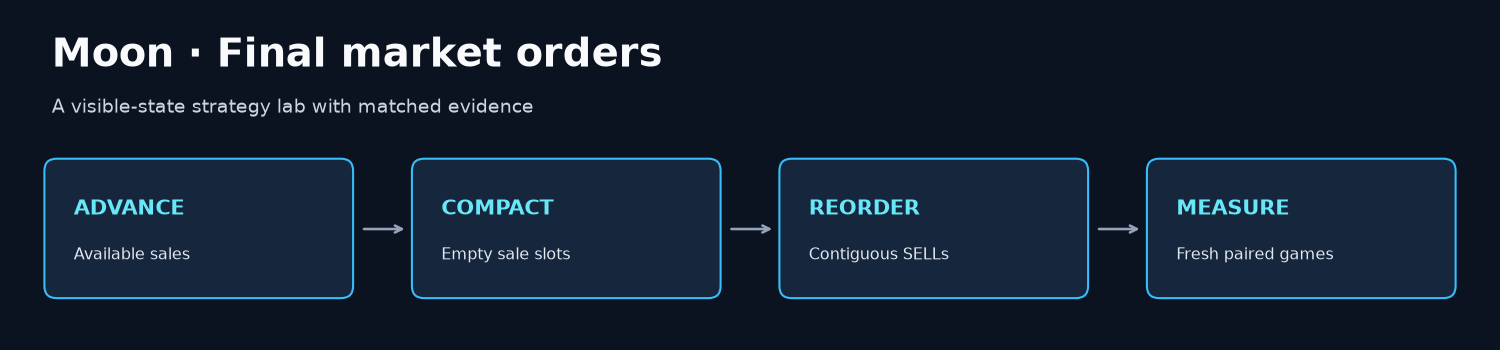

An executable strategy lab: reconstruct the exact controller, inspect the ordering mechanism, and recompute paired results from 1,008 embedded holdout rows. **Latest evidence: section 28. Local money margins and official Kaggle ratings are different quantities.**

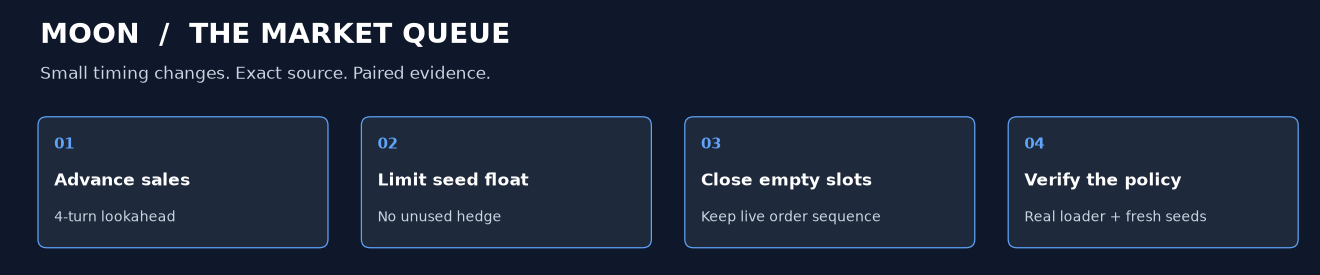

In [ ]:
from pathlib import Path
import base64, gzip, hashlib, importlib.metadata, io, json, subprocess, sys, tarfile
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Code, HTML, display
import html

ENGINE_VERSION = '1.32.7'
try:
    installed = importlib.metadata.version('kaggle-environments')
except importlib.metadata.PackageNotFoundError:
    installed = None
if installed != ENGINE_VERSION:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', '--progress-bar', 'off',
                           'kaggle-environments==' + ENGINE_VERSION])
assert importlib.metadata.version('kaggle-environments') == ENGINE_VERSION
print('Engine:', ENGINE_VERSION)


## 1. Current tested controller and provenance

The controller builds on [haideptry’s public source](https://www.kaggle.com/code/haideptry/the-2965-master-hybrid-engine) and its upstream Apache-2.0 contributors. Full inherited source and notices are preserved. The new wrapper only reorders existing contiguous SELL blocks after the other market layers; section 28 explains its limits and reports the accepted local holdout. Earlier dated sections retain their historical source identities and results. The current controller has no official score established by this local evidence.

Run all cells to reproduce source verification, the actual-loader smoke, the exact output bundle with LICENSE and NOTICE, and both paired-control plots. Inference uses the standard library and visible observations; the bundle needs no network access.

Current source SHA256: `178ae0f727641cf4b618ebb98ade7aa1a1bed7517281aab9849de82a59d8ed3a`


In [ ]:
import base64, hashlib, lzma
AGENT_SOURCE=lzma.decompress(base64.b85decode('{Wp48S^xk9=GL@E0stWa8~^|S5YJf5;iF{l{#^hOhz2Hz_;Cr<$rP8`E7`n;-3(D9A|Jb{;me6Y655V@7DJ7=zjWkGWTjZ&{-;^Y<d0y8asj>GbVj3?>)YQKVe2>}@D%f@GMwFFT~=WPfcKd<_n(FPvzl*Apgc%e?a~rl2BL~hGDZAev!`z={``27q{1R^g<0F^A#K_?O>{|z<Hmt6Xt>4}N=M?===xGK5B0Hsr5|6<LMjyw^OL%54hH$SBJZ<w(cF>zFgUBj<>OJUjpB#*7PTK(y&l=QpV=2y<?2<EYCmdte?^EGDh~n<KIxfem~4YhR&C+B_tvn7A=u8o01W!g0E^WBTwU)n3eC19c_Hb-H_HUAY_IS`eiWIv!Zi{?OJh;)0eKk6w$%-#*8BX155BSW7$NRnT$w%iV3q6AWQ|314MAEV+ur7%p!>!>B;6_hisLd~!-ai1a@Ec*T<TT)z_;lDCM!zVcwC+z$ZJbguYNW!Qn&tFdkZ+-LfqO5><M+MYtivw*J(D%6lc+!>+R&;P3Fx;>TM^pj!{+f$_o!A#a3>!05|gro%k`A#Wqj7aZcg-0sbiS9mx7JXDno52EB91hURWJT`%pF&58F%t?S?=L*4L83bTsG<txH&@Qx%dxRcVz{n+}@$|lE^`vt+RdkH%_^jZTfpdHfMF4tw=+N=Dr4N41!3UnSNA-Wy0;3uOP1x*T{-=+z!krh-r&E9enK*4m8*~m;X(O6X5O~^?lYhLj93j9}8=4Vgz%WJv(-~FkyH1+^wFE;s?EN&N6-QGb~;^Q;_=e+;R1c-lfz!PBg9yW*og1Ska3TYle)VMG`%ZQQx+)=}%hVt0hs_m44Dz<_06=L94A2rPZj-IO0Ff5q}{e83xLD>z_NG<PXVaT?{hQeBX*<m$gC#D}Si|xN+Dlf`PgkmqixmvCu_enM?Hf6<+6uSrPs;7&ZRHT(8Lpklm;ki`Hr^3jX;`b}zIk)n-jy+y5JwH8d^Uj}Z6138`tysS+ZIj|uH^p=t0^J}%Cb|hB@ggqn3i$)c35tKZTXq60sF%Q<QnfG0d@Z$ujdVCE8r-8!Zy@rK#b6!kJ(U&Gh8RUv6rPToB6XDc&b~T6b8s3gmtSJvRBu2_3~jCjJym6ePQM71gm0i12R{^*e(xfTC)sxtKn=?_k2SEB55<gd>_afA4V;Rzd=Ft)lW~^m6*Q<)9zi_XySWvuBx@ss$7F@SaM*6RkL^P>dc%hbhS3iU5tAyovjoXm2d-Q)nX9+UuQ;$Vu7Scw{m?CJfeyT{at9$`uY@WuCE;-GhbJfrsS{a~H^D6bb~M@+v+T_WKo143>(-gzU2AJ??&_(=dlD;@COScaX4~kKz|#H4$?(X88ae}>^-eWRR1#jf^-W@-xMF1PzM7K$*4Y1WA#@*`d_)N#=WnOBlff!{&<C6MXJ|?<agzLGOsQee0+LWxslbT=6i@fj3RFGJR%NeU{QF-`BhLne7mmOx*uYSmm>6Ky1&05Bz-sM7Kqx!W^s=1@9Y*XPmKBDBbt@SFtp+@7!NYpB|4)%qcJmV<h4D-;<$!06Pr+)5GNFcPVYTVL4f`~n5w}C?FC*1t^_CM`5YA&;#6;9RFu{Qp8c>_#;kzHw$W`;RZFIl%@(Ot;%kOukBpY7a2IgQ#71Yd%0k|+KbY{hFjZcpZ?gt`ECeACJm9Bs}zsv=@9;F))5f2f%d&@te>Xh`tnaZkhk<QV8ghq%f8iPIfVDls55$BFy(GK-zI=@80xHh<~)O6T4p)23vG8E_opxdY1)tFtvOa!_vL(AGOEke;Z*yQ^D@39EB{F1u0@`_~UD(-CTAAd#<Kq*pF%VA%l!K>OQ;}1GZ$JSIiqb|nI#MYo|%N;jiKT^U>qZEho;}|VWQ4>IDRH_l=ewM@1Jfk-h604Gdg{hN<Y+FGVLCi+oamOQv{FAM3iEeuK!ug-sVi76tTwei(&i$lHuaWa@%q#B>s___{)tsZ-u3qhUGOJ(PZ&5pGT`bwZw!8gYf`X`~^Q+J@zUp}rybRab=IL~^Y~y9siVD;iqy>_t(q~g!Pdz;(T6+CI<(%4+oTFRb;B}nZg}`rXBNhc-^GHL%F_JeY%CRC^hn&{giX!EpAStX=fvap$dCPWcz8Y7*8DQphj9-<zHJmyRy~Pb3+$6*ZQ=-q&SJ+&{&gYD0U$`&v*`Vy#Io@L($}17%WeaxxK~Nt|wk1Nr4Hgr78$*k=h25X3yP_}_fXjyUs(AmpD1+#spe{}$0aN7|GuRmD<#W+Zoh&+Bf!fz{^98p0=IAn=AY>~7p;$SvTfNGET5Z4xZxB}?*VG5yZEvy*iNW7!^}XLB@&|K5$#_nTWr=Gy{Y7;Vq&^+0?OQhfazAXsMNHB6@L*h6uK0yNK7S4jMsrq+JlCW13^u2WgX5ym?CnwD7^^&?-N#iA!Zc?`)(~N2G$l_0Ro_AhAvm+#j2`IECX)zz12w8R{y8@43E$S;zshTIOo)wX^e&*t#iqWR@#X7ad0cvGJ?;9`xJCyos7C-#GGUm8J|Myh&)};UUY#~m%4_a4p+>#I_oJ}}z^IRE9e%+UjUQh)Tqf<K=-;5TpAtU~xv&NDEDot?p&E2vtuX0s`sM4@-1Dg;nYtp#U!mYfvJi8CP(wn8f{~sHAvJZZ!>xV^XE}Gfs8kUDd{Wl1X(o2vyimW`Da%Fr*x!=%d?MDX3#3kKI>A9BINVb||Cx;CU{Lw;Qs9=@!a~|@M>AL^A8t93S)qR)bGtbT;o6nMrs(FO(Ii0(4^sAJmxae&s~C#jVA=VD)ZA;8&muwPN0eE(ykSK;P0jT>y3|!*j4Awf4abv<T0L@tZB<FuU@qyo3iwD<MQ0dAjrU`F9R8T2#DLDtJ1KMa#6wrRGlEYHvrs24n$X#)G;>8M(zwM(n`hWA&k9}0``|tx&)2#3ti32|FwHrWMFM@i=5$<)=Z=#@4%&FsT!mbi?t5sHlS2m;(go(m+PA=4SSF=W`d95SGoNXgBfdL*)+Whipme>!69f6z#*SoYHk1fMAwjaQ@SGHNtpN2L0+uzjM)Mh%Q*TZAcibt}8rOAVM<xG$yuvr-?$x$zhBcRH^<RAIdz3+?^D4&Gx7tLX%isZTR#B5_<>sRro!N)iTYn~e1Xx*tcWJgRsPqN3#oN1Oa#G@KpW9FICW7bxy6xv6^$M@E*&lBf0234!4DP#}c)gw(q_V|HFekg{S-89gi5KX!aDWz*`Bp$s{Qm$)4#VI^@0Mf;iVv}G6%K0uN4_G)`>NieXx{MWNkU#Bs@J;=cCxlCb|3ML#aRnjuTqMfd^uw`yK9YB)RoRkZpp&Y`WU~fF~~upE}pyCoty2_Xnqai*z<1^q@qrH&W@EEuG`@0T?LCRq)c7GxZOB4Kw4UGkXfu0q6OfQsJnU{;+5jw4>8Z(RE|l@s-%pRIH|Bs1otSB6dik<PjRz^Cn=azwH%SAI2aMWtV$NsEyl&na1gIIZoRn2J$sYn96OxnN@Lu!THE#!lT8pe8*G1UqE+PVvRh1w=j{bLXL7R9I=-CIOUFaSx+c@~ozXg`W^&@QX%&-qWKB;GjIPqj&3jIsRmtYO5B)LnW6dzZZ|V|j73FO&JLfXM3)=Nutr#Q2I#kn{5Vm?Fdi~ND<4&16&K{EfuW8EvcU^Y9yf->9(|%==;gN$hNS4-t<$aV$V1(HMtj?{>*Av)5Q%n}H-|j=Vd~_UirCSttORL+Zb|f3M;&8FjLp||roct%XGt<a1SE;Id&@)cW(tFM_GGkyJmJ;LE@sJh2sZ!Ocv_4vzqbx~dqeZuk0!GJ3!T!ee5in87X+TX~j~2F|)->#9&sdwd@pK5+W%q}r49Havr2_;AO3sA9dIvxTOJ5{S8_#sd$|H~%YeGGL-m3a!mpHJ5t6~&weVlZZjiXyyH4h3F_pMW}as(<TI%cmXo%&aLDDw<)uuc+t90i0TGl?oC1MeKJP?cRhhP`^$0uQB(M%Tm2{uq8~?zR9Glw_VFn!B4#@hz9T#x~Xss5weuC~j5IZfhfk2$ybTguXO>3Dh2!A=apZt@9-THVNJ~;mt2;3^}I)aUTTx>ziqhv=*6ukfUt-rEbQc5krk)8(K;SF=+cpf${?fmsiY~b)qY_d%y+~diX79&|@s>bYCtfk*J%h=hUu06ky9{yj<w7X9AH>B`f?`ZkX)t1bmR`K!VBc9BxU9<a4=3VTzonyK|&kZ62uloUz*V^lTQs%=BM;0NB#6&qJ21EI~k}8=>Y?4epxpxAd!cYfk(mA+4Wy8i^LyZNf$lB>}0Kl1OoQ?^bf(w}z(B#j8~^k-5JxGT_rBKAu(=RW<JKp(E1~mmzx)Y{m)~!O7C-3sL|^G?eeqq)aH^83yMR9$`wZGkzHmHOzx~h8gX=Y!t}Sfj*H`Pi@@J(v*yYDyt6)YoWVQauz-HmrreuskVKf5UcGgj*^GR7AjwOQC&#MPhjr7fHp|pr3-%bg&F3|tt#fH8<k3cpCsse)iIFR3dGYVN3YDZAjHnCx5eCR(;XnZ6mb2WtaC)&xuH;L)C}N}wCn*#Mct|41!*Ju-o$m6@~bC~JV@fg*g+kyEy(?V9uYctzq@XTT!~e1Rkxil9QaAPUORi4Gv2E@9TfW%Zf9Ovcd{W@*cTUGjBn;j6$L`}1XGJuw6h++Yl`wcQnxYq_j`QYCJ5N*Ih4dVg@v6{_`s8a0~&c|YL*iF^?j&}4oKJwOCJWqO-S)NH2pwo)n>Q>e=htsVjr#O9WN{!s29H0JF3kij9Kgu4sM*WY!MMVJvxD-9OzV$FG;0-Ti9byzeJezGRjJOg`x<od|&17ReR}{lNFE{i(k1$cjU0Hk#z3kzVXw@4Pj?0u;O2(g0p|6b#TnR%KiJ6Kef|?mu1QETCkk556Y@z9C?HviyAwO-n-0a^D87!!Jy~XQ2_U*me3SF3XXI0j^=4~WR?TI2rQ(sFLEeAQKzhkId60<Kq3J(X6v1!Qy(oPCBw7Pm~4(Io$_D($+US9_&c;4j$yc1zOuI{=oeI;p8_LdLjTl*B7=l>?}^<3(k}X3foRH~I4&h0OGo4k$;vkZy->Z+RlZG7Rz;T$8oO6*ftf1Wc#(?VWKdF*X^!5%0ZiBO4^2Jn6;BIBHuXnH(dpeeSjPoGPgYd3CA-+V*b#>QfY$dow3&k*Y@d;fxIT}!qQCVT_g>smdcfa7x{IOw!9O3B)$oau6Y5_CJVB}fMB*qilQ}IFzucy3IqnNdUHM-gv^m{f>ZWo?hcTyN8<9U|9HQ^(1gs2$fR}ENZF8$HE$%)@G3q0kY?AP)!5OmpvCe!R*6lr#n+y?k@tbBbDT2iYZPlRih~e?0Pi3s^K^b5Rwmnq-xn0YESr)iB`)DhFH^b_DAhJqw()q~nsQvM5GuIfYAs6CL_#ym8ZxhQ522vevQin`Dw||UffoT{truq9_BD~%%pm6xwVjmZ{2$nFt$o!=wo>5)7jiBO>&RN*s1yFs~+=;)wo%mDii=<kIDUe3v{zykq#rpZ@i9hhKx5c1;iq3jP*8yFK5yd<E$7((%pc2460~x(n!&#tLK7^g~<4!9eAy-34#X9jmZdOA}*=hsylL5hGRg10X+YF8?X#1?U$Lk3J5j>Xw!6Q_756?$8*px_IaZP3P{XgKS2EveU6_Q4xH`_%pkw|8)jwa$^2y#2c%put;Vsb8#jXE>zAnNzGm_u7C!QUs+>GNyR<ToT>#y?i-0YjX897mOMYSDXNO$xC%dUOQ|UW(JCkr+jG|62At_2ahc>HU<Ww-xs>h{b;i5h|{@%2@fmeF+ehFzV;0J>LJJkOxxOmJ&@4I;27?^q#hcV20+WMv)<`F>e}|_#_@Y)@Vr9mL2!sE`6S!-eIDn^3$O)&Fdq!y!)vdmht(kqa=V6xbqfmEbMBGo>L$^1Sq;GEFKADVZB<;68W;$$76v)o1!wQqx4;<YSGpU)f5z6<tLUOk~OzKpjG#Wt_bx_U`CHPB#YJP>p?qKbwrH9`A`R6u96o3r&@(*13P?d4PtsaImpn}!Y17I0n`heznL|Bk^z}MQ~;$1=*AsuiUd>P!?=X2!dEkvco!TbNDTJ@xA4qO${^{r3DD}sy#;pr*Pt+i@pTd=<n;^TVK&y8>MS{L{!%gZKJN6wX1A4Gs+5z<7AUy(l)Mgkz^U3atWQEFxHYByAEOF(A}RZ8l4}oLLb50~V+zQm;R0KYG@yLO7(P`^GcBR<$sUMnyhjlSgoYNETW1Fh(=n;`uaEo{;_u-8aX*bb*7s-*vz&F%x5JQ1nn$tz{2<ldmto7o{V5Zj`WhoWNvM%2DT5_n5yy;qrJdF?{Mv0S&8+#MB$7p=rkM~)NVIS6(1Haxl&44sRWxYc3OMGjQPi^C*g{<X3=^Ay!x%j4TzsTYO?m0@7b5KYP41)$DcjN+0MqW5OvoCsrAg;4@gYxl1yRvBR20VPY&Iz0l$g~4e7ZbKOKAauWA2Ve>+YmXWp43vk_0u<OTH?oAcwN#pp4B5Wy}jKYDUBwy>n@c;0xKU$_ax$J9%yO=&auHEkmkoJ{}0WXehvg6^-{@5SXcUx+`De#6b47D85$G$7M`T1<j^ndG@E_TO;=&SnTBN-F0ZCLwEd<@Jde4c;p)zhu1HZGY<<`r8*de7%Pj$xv>3@n@Na`tfzq9u>!Vn%_E&yxEx?P1dy-5@*J?R-UJDJ@&`UmKBF+_%bq2MnSKn1cHJ-N;J+S0$$<CKzqTDErNG7=*W-A>LVU+UuVJ)f;Zb&D!#RO7)j_>BLlTa4qQ48knT&`n1%HRKtcD;h!YDN_Lvm^Jmy9MP>p`78c;5~tt|w(wC$&xgq?B3ah|(*$T}|F}J9l`HrhMqF7v+Th>iaa?>exU`G}&&JCK2A&isnm8kPQ~7BwQIA4$7$+pfuZ+Sgdn|fSP3*m*UrHhobngPg+t*hzH+R^v#So=+j#p&gv>L;>wz=Bj8%oei}usp#nuSH9izu(mb2d`uycXh^tN7%2H64{P9WitBlK9|LfhLlkd0KqUYN5C*h_6CCJ6fK|{?zl`p*7j9Ll5wVH!K5CgoGO1b;QlkWc7B#Ylsq|AGr=Br#GX@_KliJvdxBIHGhh(ME?m5DQtHQwp^NkueDX}$~ip&ns21vpA8QeB>-4V}_z7`dS*8n@DO6&Wt#51e@CxOsaS_T$`%@v`U1G~;`u@coWso#`vLP-F?F?<(?y8nL?dcWmpIlzBQ)`!uu5c;(g{91SQHF2a}B`zU^M<7$TP&DkxS6YKKC07M%vHC6>slIV4<RL(V|dFm6$O#_>X(PSN;x9s#%wZ<I9RYx_aac!$Z7%4l&bOJQ;0Q539j~?GVdy8$U{Y)8d!WqgfLzlZXtOY|7+TILyVjz9{L3Vh6ToV4?wR^oY?nwNzG_BxQ^H=Us1ShX&?UMBHK`$p_bUc}bZYU4ehe@l>Yr8Ew#0EZP^09~R85;reQv9i2u;hQbn^B@*Q1&@|j`(diSu2V|W~VZK{{cFg8$xGln+TB{Z$)M`A~6tvibGMCbm!0kL4GGHE$bX$0l?L&+Du4W`t>{s*EN}$JYnkP>js^yOHjGQ=)V0Lw+*WFH1Wws*K_*S*>2FFNWXlyqRBe0FY*}2X2#n_E(?>GWM<NqU#{dLL-))n`%>8Vg~}W!AAUzatfK%S9sFOhb>Z-|Cg#QNP|90qQ2fPk)TCM(7!5)b2NAC*p>={G8<A8B6Pb&Qj@okYx8}m*&IIhOe2*$!Q0$o#z=VV7fPFJuJz=6<YjF4Xwla&(Gm5N8S0l6w>y*(~@dA!QOp*PGE*!q<n1ryi>|Q&%mr?j@O=TB{KJD+<!|PQ4AeHC!0aJUli2?m5O1nn`Z98*0GBc4;5*m<>-yhbhn-Ra>hX0DmvZ^PjVbYa3mwqTZ$dEX*%~D*;?Z`PDlQ-YA$}KJ3LOS}yus_>oj0JSHGSu;=rJxS4>DfwYttZnC-R*#qEgr;33}Qnp3x%N|y*KKmwt9NeQSrY(wo8^~co#!W2=O1*#nMV(fnh{EGE31;^X=|;KZ-Y$%M`;0&J&TY<yS}JT&5kUyqq*f(a8K_Vhcu!L4O$mcu9VSpz6}Uef{5yK=?AU$cOzVX4hP)+xpn7kxAsqE3ota6mNH8><c-z5$zqJostZ!Rp;ovwZ=<Wm@-v#<OC7mMm*>=tnG6bl*B=%#_&2gd{W^$=ckex88KCH8YyU-=Z?YQ&P}c-&~$EW=|3Up*Wx}n5c63@bX7XbBGfGqt)favTqd_u`-3>&bMie~hRvX;yE9)HSbHxGUi~~pX4c?ipv6!Gi;4h{$0nB4Z4Ja;2tbULIxb@xiQK-7ENY311%eEI5DF)9KV%$wfe7YVDfMTLXcN=$su_g`P%S6u$mXTTL6X)HJd$+7l$YCrRO}-o_<TVw!oE!-`Pt*%(1FpAh$wG?8wTo-pP>_C1K;&(*)NqYUQM&u&D@XA!vNydCNobvm&SyMS($S+zx6yK&NC#d3<6SS2Hj1&6VdfEG%QR~Ls-eKOV`SmAI_ZLSLtLy-{q|+afXp``@t-NeP<7xL-=)J`Y5IWBX@jZ$pc+AWc*7mFY>Ga$}&DrWk7-A{in^^2KVQWI@$fidp;?=&~f<7T5n;cFP0Ii2}TIlBoK`Xm*6kN*||G6Z8C}i?ddkQ8#N_xE&(a@<CyHo-tjWP33>7Hpz(Sq!8UWAqpK(S?XFr5!Ds=96)DtqCF{MQ9<I5Xo__;lJcSv)Z8>Bf2y%$<IewqaYmf1gj%{zD9GGUH;v5O9#!4}q_i3g~I2EmAh(D->IHJ*Kfd$w_nhs{0|LyIYuHJ%OTw#V=nv-R{R+JK={~=Jc7#$hmHfe-po!gI0$>AsIN+cZQ-r7lL&{GB9R(t*%VHs>otlHb!PBNhdA>&oET;usU34zR}Aze_KL}PibDsaFREdTwU5{EEImNY9By((|I%@1ii(M2t<@6LY~n~K6PXS>0bZid#`CBnDFtOp+o(9fECe29}rrZJrA@IKRk*#Il#Z|Ab|P9QP*^>J?>oKq-Mki^2>y+K=$pg_s;5l>nJbw5s%KDeU_H`SdNPo$U>H1;?~0!1HEE_u4+M1wu`o1eh)B~y+`szNqPyMLn*P_Ts-TV@`4&Byx|q{xWFUEzcnvBLr^L&jD%_>*8r-T38{x}BulPE{1O=|8ToLoSqy8KPimsTS=v{HMqu&NHePLC`L5T>bq_{ZcFG^zlt5)}@k7piZ1LTHfWvaj0x#S>?(}>QCzFDl)Nffp5ajm<lcBM{9=_{zrm-FA`&a_kGz8!l6&A0U<PES-=&GgJgeAcxi2CR>Pv(MzkHSUzTlyCS<q7q0w(!GQdt}S4A8CvX^*r;OqdNRZ;q+oWvnmv$k#R1Wr##Fg6SS9Ev<H^H5+KyS|TZa|Gx6_W7Bc{&gZMni|+7X4XjO;gP%hbPO$wbc86za*0#1M<XJ>OHD^e$};qU7<X40Yjd}=;+tC_F<6%@G?pEVB589WU_0;3tuJNm>L`q?V2&U7;{Vo8e0vK$k(RlcQgpYSV1BHN5HB3GrR7kY4p@=4bdy6VBx#9Un`Mj?!4qH2oLOmhiO(`p9J5=X^k8Ci^JQojbT!FW(14zoWRwf-hMn*oxLYk~kD-(K>G$9~jMEcd<z?i08C?|;*N|x<Y%+xiR9=IyJ^&|?7qOkOtwg&4Us-Eq1_(90azHe@PD*Dy`*h5+pO$tfBjawb$-Vmo&SJXY(>cLc5Mba4vqk4IRE0|%?sKOcX@3F(Z;bziNHo+tjxTO}cMM@&t3HG0TF%kkoEe1Ty#LCOm;2c1L*z^>a}bhis!9}bhe)`3Au%d+MP(Px#F|#<R7rcBv%NOQKf=HQyf_YV)|`IV$I(BJL000i+o0DTJT!?iA4az_@4SGx&Km(YNB!tp+`HZ!m;VIX&g?X9or|S{34k2e)>*V~Wf4pMQ(sh$wYjWeVlX`HJn|l$=sE*%Sx#7C5`)Q88gK@+0*j-UZBvL%4Jz$r309||<ycoXI)Bo8aa(QuOzp(Zrmk(h4Kt@wHlO0fCD?%L)<d3Y#;rmA%kh9B0n~L5mgPM@=Taz}?4gZgb#VtJ-zIEv^CNxdoZ9NXKK)G*4N`xSHmMA*!hY*BcSA@0sVrpqnUmG4iie-hcH*lr|D9MyKE7NrZbT?VKCc&|K2n}fiW)G|!3*n=na}Qdo>&W!>gQ)8pMT%n0FMx6;q~`^+QtoE>1Dm{y@Mx9AB-^}Y60!UWz{qi>kWx~;soQy6Ub;b+%7XWh-u%;z}~6pMTAY-&RuGcqV2)jS4~kEW~R^UGl=Ao4yv4rd|!ils8@fQXFUbQvwx#ovmc(v%qCHQ8~vlNyw<_S8YtH22{#$;&)=x}fk2J%QZs-e*jl~tYHU#A7t6dxdS4RvH%x|-bL!1zup~U8-2Qlle>)c%_vMhjS{Fi?2eQloqkSLwE8rGl*VvjFOtz}sGbn5aWNVZ&9y&Py+#Zi+V`h$Tn1``PL%~Hsp;^f(uLr4cOphGgMfk3iV8)o5#gv4nM+x7a$IqJ4IkZybv~LgTjf4{$`=^=P!GFF_Xw{}FLS~YBOEHFnt%X(%5+d;p?wPUbBiRTkuK#%!Xk_eDqt0q!=W3Z!JXHNbEVimcm!57e_D>gBiw>VNqGlnMR4(GYo*Ct4&F3BZ#TL|1K-5*rpHsU^?%yXoxCnFgvi~fr=HX!3&-Co-M(zW@Xue~sj>Odc(9kSu;=QiG<5An=q#fg^oOf#<b;K%^H%EFwaeAWX>$%C)ol4bj3_kEA_JKH@&EZqjBPFgw2szP-vEc@MPeoqbBykoLIp&Fe%sItEf)5N_`3Y)xXs%0B3o7VXS#X0E1fA$k;~>6G$7JI}3+v>%nYnM0y?dx_b8|f2Yi{5Ump{Q<3}aX<n5=N{@o^|X^rnF1o}z|P-2Y{Dsg)_BW18i4H;eFBAc61#M9;j#B)i%S7^N9=B-U74#qIqH<H5;uUq9&+N^p@qm*h@Fn;0$_KV6&kotMC_YAQ_-6UW5l;87!CA#ffm7^+hHG5kb6q?(?|Ih?p|+E_(ZrxH+TmW)MmjxJt99Ub~j(0Q&@T--6IvngHIh}q%@J)^+X2Vz>hG}VQHTF~Jbb6s%`kPE2q9+zKtAXJ_p8n*tpf2tn6O7&#}8XEdmTur!Ijb@y+KmdU~E$KZoMgw{FLi`*5B?k?iT%<4D1=oWO+w3$h*4=|e5yi69AojM^T3IFOIHeXoSP|PLe5we$#Ml305enkZa?Gn&R=~^9e+-_LY`2Y!_cTAw02@;8&ASg?Q3I=rX-Pso2>GD=eg3<@^V8d|W}H)5#^o98VSIc%%BLO@rQoCt9eLfi{JE%EuL{6tUVDe9fpI+;9LS-l&(}ieIUgA<){XOaEPGZ5_J%ik-pg0LKC3kuHmPRnD!b2BfGD0dWpMAO4_R+Av*s{+icfLi>GN=^542#d|7KjFGDZ%mUD_UzrzIXr?_QwfozPVY#vvNMeVn^>(haO=2XT&G@=sjG`|fx%>_GUjNOr(6PRjL?6dZ>v#2M(GsaNg4uU-vjE952fkM0`R47N$hnjiP5;8*7`b{H)Bfp<{$uxIv}Si9LWohl2b&;mAi?b8GW+`{pN3W0=&seWhw$BVnGoGvgvj6ul{TBS)CUP6VWWxb@vEhn4|;BRV&_?DlZBG6O4oM~+2#zWbhz0)28xkx`)Ult_2mAfHV^T_>z#_HyDRrT;>yYEKQq0fVuOj)Zl;oB@iY3$wU)mZB^u7d2Ggk3hh^N8CJsc<k;rNwz6V#CS^T;F+#P-oVDeZs$p^cwe2?}r47>C0z7)U4DZlOUR<sB}4C-ban$AVRT@(wxRc-NO{e`KxUJG4`;FN)x{8!3J4bH+?^*m|)*l4GZauKo4U(Fk0RAvp3??$|`3EjTw!AEY;cn4{ZQ_&p1Y?391)MY1~1NkTILG8^EAT3C8aBX5*uHo2R^9CaI2T^^4f*K%xo|4C4*4^2JnR6eUqg>q%l+qxar{9y&F%Cvtk9o%a7W<}{OgnbKaLObfc5-3h}TizKbjv|Xz}KT>)g0X`aer-I+E_+U>&h!j8Bg67EN3Zu)BNDc+Aa$(9oi>783pJVdPx3{7IO=IoOKIhzVp_W2V+N>{kia$pYHkD>CV;32i3=x`>TM>q6-xjJW{vm{sRMXtbJ7w4^w-D{%soIB#jDX443fn{KF6N9sJjLKe$Z~KXWIi)>#chjqgO{|rH{vFK^84h+mT-cU2E(>uzNClj8D!twm=ge~Ua6<R2ys8<>2)D2B@oLvCMQ==*{Af!cu8FTYBoWe1IK5rDnHmZo#Wj%3_Y#75LY_m_3*n#$0vvQmXYsd&mf)=hEso1Z4P5$cfGv|fnweod#TE$Xb0B}jhFi1C6V+f(bjZHut%t?eCQl)7<b~?8^tFKw`u?8sV(x_uauY>tM7_Px&yAWy_0H(C2#FuARbHAN{jtn;+!l>P2hRP-X^QheTcv|6^Q5ar+>eY&<4OB{$QCicqZp_zOifM%Wj4`c}uY^sW+4xIk&lV#!cLwEEBu2Uo9!aR_R5z6$^KK4d#Sa&oz3aKj$e7AAE8Mbq<I!!kJy%fAr?xU6mgyiu=8FqyMN1YFbs(Z6zz}-trcCRD%(RV5;meWGv<`%~61UFcR7xE0nP+oC53SGA|%Tno1Z!DgKQ(6YB0nXu3gGtf{kok~>aMOmZQeQC3t(TuYP_FoJ`#Y65}gmDBI+?%00oKo3bV$@*Vx0P^VMk@$*Kej=)Dg2DA$MYV}uURS4+)F$YmSZbmr>l_2Y3C5y$vFqh7qnFFqwyCZgnDS7hEv=b!IWT~zGJ`Y~p^mAkLzf(goOFO)vHE0Z4#{(DkEHzRXpqq0Vu?5phgN4JZZ72ECCiA{oh45A$D@F+@qLvkwY`e&%0m{e4Y?-1!Ap`Us?DsEAg}=c>ZJ=$@qo%iUaeI`X7-@u)jY2?GQB_R5aQ1@@JW`6ur5Wj?$hEXv>%YoDFvyPBLArx%H!+AD!iJgy+$xuNt_PX$A0@jGnvx6+}Dy1*+k354`SujmRUr7GW1sJAwC({;T5qYo{qA?AH_4LV3Q!QK2}is+)5}3he&XJjMv$fE}7oaNng*WoB@5)w3JJCGZ)FO6~Q9<o4hxqV+Rn3K`{P|%+(hcRBG8`%Lg{`mx~~oV-DRxc#Hmvi=RtT>Z>g33D%G(?pHLRm0R6hUQX>&O2Ej(aibHsPjOQhYeo5!8sD6RG9QBtcDD#LxNr>lq%_$v`AT_CRa91If}UQ43yX7ZLyJffx`gD&4nD*`ckGhfHfYfV+vk{jEZNhgCaFi5#4UmMh&Uip8Fn%kTi2T1QBP2wH@ANNEzl*B2ni-6RYZBtoa6DjcFJU>eIBLo@X3-{vkqh<aTM__y&t@VxgyknGU*hcfWeZVC)g?_fosDYT_X2p-T4-@+!!+DEHN#ahW5>ACCUqOh{vhb?#nInw=3Z5Zi$X>EDmc*E}$uQsp{7fwJ$M{-90%MGp}_Rbeha*3GU%g2{zRuCK=yuem}pbF+zE#YRFG-S6Y9OwhKp!kp_KL7L1CSX>YkI;)b|uc>r9h?+}p&vf^!yRO@FsDgJyPC?xTf)<RbF`mUogsbWR;>c|9Idk^5Wi61<mdFzn4UrCSUr`lF~>)CQ_E!Mxbt|7+x+pb+AxrMh?SWsAeG&Sz@#`lmE`!G?9jNFLL{j~I4$rZX)3bIzfV=|7bq`<l_-1M&9zt0As0jUFF53CY*Ee3#<AfI*6#>oJiDwn#E$%-hp|0wE+e^dJq$T6N9`Gpi%Z0$=DCNa9>c4uT+IyUu^#M$+G4O=AZWfA1xuPi<qjKving4|c>cAoN)TFYzSw<o4MgX%Rlo;*ZHYMaHwdQJq~q#!Ul5V{fdNm&%m^%p3+s`Cf%X)WH001MiL*ygaV7}c^~#QPVSZMr%l9aJ(4a{Wr%!l@Eq?S8X4ixK;E0DK)Vt#zeY#X{adV4JnT!0+fAzfbd&<f*6b;cS&{7sQ4g*FE^SqJj>78%-cE@`_!mpsvdMehC*{$Jq-;@eM8F!|widhJlbbQKFlQF)-JyAhSc$eYgzueE9Enm39Zm+F5K;ju~1hJ?}bN&?%j3HLqGF<kan4Oe?>ry|1cJZM_A-t6-XG^wj#|VQpNv)OXRg9te1(^)qb7sH%RZj)RMB!G34+kD(jv3v>zhT)L4pMF<;Xr<gCV#F1&<Fr%=QLJB4UKx^)u;3NF(Q8FiVTVJq7udAWKf%K_7$leOw=N7|k&k!E`r4i;O&KwA6Po?1yPKT&^Fp<f^BMpHZORs>lK4j>l;x&)a?a7M(moYL)W!3tWpK%yt;PQBq7b~I1(#Bb^+xA*1WcN7UYnD3=c!bmLWQQ5uswV_ok#bG*o5D<@u{9m&cM#C_LZ6A{nc8OOc3Q-UErtRMB&$CFkskpwEV;<?f42EK@5K+~3hNhsv9d<%PNdWp^p%rA!6m{HffsRG7ZjO;9luq8Hk*d)5&NUz|7O9JwQyLB`q=%h38(xrS4BnVT3`~aM4JCTAhO6DT8(y&tdA7}l%@|wR>Y`J7g;mipP`*0zSQ*1Wi-ys@FN>!%B>&grWM4h&L0?M{9Z|b+;m-ATB^wNHHi242Dsm<3@HYZjgHMQ^CLfV>x&vLd<>Rti{~2_Fiyzz8voT<%6hxF1<D^Z`t9U#V?{9Uw3LcTN$mCP33mId2tBStPqGdLMlLY@nZaCYVz2&0Nx*c7He1a>hoq~Ch#rAKCUx;#cgQNnV|^us9)-!<fLZF%wylxdIu>5^W5+~KAr`hq+-8SOw*qM*{}&q${cE(|CxvJ8oea1qc@3OAfCUJcMB2&9hmc*amgXcK06MQ=_-ro7KvXwjZkC^aDLDt8w-@`AWM720r{p#b>VzWthk<(4`?q0yI`@xP-Iuf>$IWZy(O20_avdcxm)(-^+ZYKJ8_BPbD}w?auoqoTM0kqGL68Ico!bC|j@-1#JfUXB#`bPve>(_}6QEO@J)azfC@Fn~`b8Z@i6R}7D|)<xs*flFJ#zg@7WhHWYNK5d4Xlb?W@m}(M}hW^UN!I!J9XEbf?%$TF#@ANlaWP=uz$SDG?b&FlpjofVo;u>8|B=IKDto{GO_?IA7F|Cmqe7VCIcLi&iYOC2b2bF5WE?MV(VBB%#8>KoEp~s8}IJ$)@jwyhEl<-sEEAn{MPd+$6tB5hUkwa!vfA=nR|bMFIIK@!KhT4+loO2*5#0%Sfz-=a~)#Nw%S?^#vHnA#1D745+ft&Z_A-bdX}FJ<`x3WOBoH8Y~T67oQp0x#osmd5W(i|#NB|DtGn;Nok^WR0_c+PeS1xS!G%Kh@X;(;vT{h|f2?k7%3V-5%|eI-D)__bQtU1rO-=7UCwJSQT^#sc3MQ~_o?A!NDCsL(;)yN5fakj$>_FQa#d>EyNMcoryzpgY?Kt8V0Ny}*`gH(iiJKyVAo|gDvi50AOQp~U=X8{3Z@5Vgk5%VB1x|KgTC%lP90jLpr?u**5c1Rc+VoV*dlE{d4>VS1{2VVJ+1CK8#g(M#mDIU@2f~i?K>dH~zr5=ZmGOil9~=z7iV?&~jL2Mg`7xwRt!%)kzo^JWp|F=ns0WT*FI2?`&I2CJchnC+uWTo;UEwKmR$XJVqeHeeQd+f7Ytme4k~nV4&(yMGGf_Kh0wz#gw{S5EqXP>oG>fa{vMM@P_V_Dybt#j46u}THsxQIK&@D{vD=<M?&CfV46m9UzgQmO=g<_Ko;J<=L+jaZdRqsQ|^pK(YbXJ&ScsNP*Oz8Vjo2}v>{h2u9I7mt}Dj$rf>Id%<cdvrPbWdccg`SZ^oV#^utBfO>p<9Qgd;Ne2)9wub#!<dNGs=-L?2w|caap=-aB7B$nU>}PTy*MRZb$~G20qHY-x+P(KvRo}Dyg>ixvH{$5-ea5fyn7KI$a7P$Y^F9L9bNJRUG|)<X=N}^y>ML@1O4&V~-k^<N@Mi_f_#`-7NHEbym3OfX~9asZ+7c<ptn+vcx4yfD6$Az`({)U6Q^uj;@55Vq;9CY_wsyw1k{uV>_UY9e;GB*8XJiwa4DEQwQ<OekUuzNG)fUtBI<fX(KMyHX0yU8L@NTUKcgTxB)&%_|D+@aAG~?E;x3{Ny6G1N1d5>9Z>t4XJg0Fi8w@EKWG0T>zzSAEAA?12qj1dMWU4{Rfm39A{`JpBu2B8LxO?pmZ0!rLrB;yS+-{i4ss_A+utJAxQ)X__eGk**%AYMOLxxNSqdMSV+rd=ED6U+@7<SnIX(K2L0KV~@~!4Xu|7()GhU|@T-K#pmB=sEJI}2I@UoW)Sm8oM;-@5<vO%9>#bRsY1DrKyG<Ty`<8swKZuJv5ngFjuZ<uzcL#3@&*&WKO_E6Qtu)$0v!+Br)(n*pdwqT~fdcJ&5T(H6<B~lPSy-yXos=b<QLrf@9JKPV3;{dNg?^pi2`sKS2sD%4SdthbB&j4?<0XH>E-wqZZkfW`i$c`z{rrMd~jDDyHQU!T|M^9g4o{2Iw<R)-LHU4ZAmNy3H0+x?GRqgYX$LHXnOhn}F|7)-~DhRU85GQ%g_UczuQWr*HiB7dMDTBYYp^|((sIpX4030r`qCb&(I0p?od`yge5(vVXNKCKK!Cb;Pn(%;R;f_`*V0Ia;cagfYDv1}hsik8tN=PTO+ZbrX+OPdpT5k26x*3T81bN#l=aXz{%t_|{ioozA3*F@r6CDr~p5uq7nALSEc$N^6e1kF0?4+N4AROL=*!o06*GsSsiIom}{>uzTed;ls9g<XV^#%rTGe0mQn^tl)riq<kGwk-~c8B~h)TPoEo;!@{w}%<&lNwo<L>qW^e(DT9_)H;BE9Mr%*tjK@PBJ6nMfLN$mt_{i$I1_h0sc?Nqd~j#dL)^tbgIIZ(=?$UqxeP(yARScB0cBr?l{)}af_0f6mt$q4p@!_ZQ6k?pC{?=osNurJ8qz=A^qROrIk2<D8VMcc>YuT@*K7dL(BjnDKktN*U;yba=P;vD->+8Y@G9eCI8gotgunB{=^$M@Q}Cjb;(}30Vq^bR*26eBMrpU<Yj7sWBm1Dtgf;qzHuD(0L9GaN39@ZJZB>R2A*UaUK^Yz|7W>-fum|uw%o55AlPB=oYeY&`+&3Pbuf@?wll$*)EICXUog!o5!wP{Pa^qh*Sn<SLaZ?E-0rNMoHn=;M=>y2M&xtLdYk@|;dM=lLc%&`a=cun<LUA|t5@ZzAn$|<`qCDsE<Jg(-NVGG{y~a`n$Hr4v-=IX+fVJ=9otthjS@X(lpCp7uvQ}9(mEB1Y?Hsng<jSG%Ze;hwM2n<;FwD83O-_o`-$-nh1_U^XZoPsxl-;`Jr$^E`_)ZCgIl;Mh*YUT$0HF%{|@Kl!kfJR2#-X)5<Ihzq;^rh;-9saO3%X<@<3}p&v6Qx4^y{>&})Os*eSjb=aQ#DA02^Fqp>gq6?S#RYR?oIg;TbXi=@Yj_T6+1uY2QhK?#z{TY``m_TwIO&7KAGn!?wt{1m_Ur-3wBdGknI2k>;Pa2dm{qnJq}gqS09qelZ8!IP+ZDg2-z-M4!_L~{!R4w9vEW3YBzw-y=9Firi<Qk^#zU6?lQKfVLG;k>1^S5mV(!$7G;pzr9sTq6KEB`Krhc{#HhzzF=(%#DmUx6Z@Vp|dh~WbqsE$A5q^`owRNSRoU$AHH`5dQSmK1>o8h^OTsXEL!v2Xgh<4m&Upexro9H(C4wYT^Uj3?QVLvr<PP0-P&NAnJHZdp&gw>##=la+ZMRn+6Y_5>IH@Lv!>Ibh`PTnS*kgVZA>Ak4@)P2qFmycp7883TaN^yR<X%|1Si?x##+2NfXLq1?WQ<da>penpgByY4=)tH51}ivNvvU<l|pVym;((#xS;8N1y+szH=n4w8#vt~OeO3Z5I6Ag8;k>tv?dMd;iQ3D+WXH&lKv4)b@soI%O$Z{MmFbIhVrDO8KQ^~TzgOu4~ScN!Z06B_^T7TpORWJF3dxx;KXV0d68>!7h!S-b7wVO5(pI?O)Rp`PF>0`kzS^!95}rfg-1JLbW7t_%0eEcl~W+At<V$v(wgLqSZ1ap@{-3;l5kIV{|1_pcpFo{qiVI~qr3D+UXHp}^f3ta7m>+J#qWq9mkQpd*ybGn`0W{cu#JV0p2Mwu0bqs(6ZxUT_q!Iih5R&ogJev&pqk{8eF~xZy=a{o4QL-^eVV~%C(k}@4-?C<kVLoYdH2s~Ft2D-L#23~-bL=P|7UWC{(Cu7z>}+<WHI}6lesv=fI^p<fHy~<jW<DDruz&dO??%D4Y82rghE`ms;r9Q>r84n%(|oLiE$`?;c9LYND0M`?*b<>E#TA&e6+|{444J*AIje$L{OCTQx`(LcDu(q3Zau+%c;@INsfZU)~k+8Z$pL{zd1Py;>ZbJ#jXF8l$CqTVfKh{ho9`KAq@$~jltEFtHyT_2$V+2(liKjwBJR1PV{*KI_h2mc)3;aa(fVriR&RYSep3Wdao97th&OE_CyWP;A}o*m#HxAtGzDBfX62XuUbQCQB2h}MW|40Gh`HcsZtVpsR!`1Uhk08e6pT-qp4Xd_Z8&MPRb3s{TH??LJt!tbhq;Gxq3yfz_u&~8M2@imkDA{UQ%pX8#-HJzDf_?8htW7XheEq)Ui+s!pAW{bU=W}5CY0FP-i+_yNfOV)x-5uMv|ox*u|t5O4Ye^&Ws{XA#1Q(9yt){kB!d0A|T5(fR!J418x?_&fYw(McnODrrHk+A~6+L2XtYo8{V#s9qwkYBMMscUSz9q_fJG+cB-kX9s-NN?ZFBQR<0lQ!M;l=WM*$EM#HkAX1jYx4-Iw-%u_ExMIa2GwEa}Jdz_RCMh_et$;j|mTDd*CAu4{E4W10w7*y7B@+HV~gRZK~IOrWI0d9f=Yj^tky)O2L9%d$SI83D5=2_C<_RFzOwY<QB*>EPN0nD3bYAVEDEvuw#<#Z<4xPh7;1HVBtAQ1wS*fC6Niha#;yK57G+f2((P8`&R&WN}CxL|SWg-BwGap|&%5>)E#`^}p}{apu7e34Z}KRMay8cFS8^Ih9kZ%=-??PdLTj{h9p`6EqP2{%E|z%c1*rYu|*)9{-3!<@nY3KOcLfC*tID@zJV)UU9)2Z{DfEO(0KNGP~gy=}Plb@bIh{c*i;v3m;W7V@pZuNXt_0HqXPpBd`p@CL%)8D}Et(ZKNaUKEQPV`JVGW3D3V#`5>eHc`Tpnl>ajh*KeyU=BvURdj*`>Hlu8RxX`@F*G9A`|>BzVvDpZ-t*NB>FY)PIDbAXUyN8%ffOpq*wnFu<pt$LF(XNTyH+*~e>i96MphjKGSR9g*T7c{g`ff$Yh6;gwa_WS9#%<m*fl=q-gBS&g-}dSZ?o_EalB0<mRwno6^i?MrJJsRBEyJNV$4nDb@xiHh!yFxBT$qLF{6Q;XXP(f=E$_g1uKMJ+Lv@eZE9A0|7Hgq8V5sM0ZiYX{&q+VBUJIDc<|Z?%ohrYR8aqXkLw7qTErZz?8!Y5&(hS_c0(y@r&4#P4x=sa{qj?AQFQW24F%;LTYLKkl5nMt)C$-m;0b-WRMk&}pTJLJ;(3a}ZQ<s>iK8+#|FoXc@UrX&`^<C6H*-^)?rAk$>(~!a0+wPqMEY#hto9dE4usBa7kO;2kR5QFQG!F5^Wtj-j5Cvhky}o7Vk(M6Y2%7joi+Ft7ZE|@gnn$Oz>Z~!y^y;WNc0@Ulup2uniHpYQxuGUTuzp|Gd7lc)b)43AY3JEsw_&jZ=V_-W`g7C`Vk84iLnC<&hfFG&1w3;bzj#snUCpE5evC~5S*g=0gY(53+Pgj3Aet!oE?|<hy8Gv5+FrIs*y4l<)^*k<_eKu%Su}jMfZibW`U-lHw2#J5ZslvD~JI_IYkSrp{HZL^}CRborO?@PR<Mb-1C<bkkO>N(mEcZ*>(*~jGlq-_)G$t3dO_biz`w$7nx5?gOS?hA=kG&t{?z!NOMAt@;MDTVFZ2TBOSsMA%K^kcQ3P53Ak&9jRik>Yrkg|@8%?`OY5c0H1e5ORYu5(uMLPqs2Bn+<a8S>JCF>EpYFtD)}P@g^1>hIZt_;%w)D4s>vW5koigR;*oBe^qd;!mJ&<=Qdl;oSz$WxSR2u)*$w>2R^2u_WuQ#mW{9Xe3vTPg*N;k4j_&eMz!ScT}B%45&OBnn0NQLC9S|?6@#fvrWLlv9im4OJp^FU~I*E1+B8yg^;evySPml5W?I_Bj?07&)Qw}yuI+)UCjvn#CXfpFfO89nWH-8b1ZZiibr1Ot+lFA>78xAN02mNZNCC5!LvU23q0OXQ*q{?Vq8*yHsGBd*Vzy7lNB?|V%7YK?ZHpOxQDAo4z?syhBWxPPG~tH${J=n3WjZ2gQM)FZJw@FGA>?=|POd=O=C1M0Gx=Y0(ZZQ3Yfo96nyuqrxB0H5Yl-uw>X70dLEi5Czpo3#7@NZ~vL?>g;j_4}y|?y9ZQegaP4p1(1<&xq}}TqULRbjmpo_~U0#?g+tGk?Y$~>&wST3lDl<-sK4V1~!U$_y0d{MF=$;mJ;7v5q%U}&x+a%Kt>7lW1gxeQL4x9!E9DSwV$0Zn{}bx5=JI!LNY^y+jt&j=^lUm#`p#J6R~+n0KBPBzxh)Y+{m<rt`2=QAWnPpPLVnx_R!sScojxzdw4iJrBz_aaTm+`)=d71DcP3YMT=76Td>HbM<FF8c&0~z)%{$cA|U_iSdn@?o2q$kn-eTDzPJpH;W}|?D!kEEIu9t&Pn?;SM-)V&_`@r*bjBt%&--o5mOJW7FXmx$hEqXYp^*y65$5>{95BdZ$gXRdm^F+ARP3X&&%e*qli>#fP!BzY4DIq99BHJX+U1snS8u-*TZawZ1n^e4a+2?MQCAg6#b4r|TMr$6eddJW=kjUh$YgBFC~3Sk#j(PQ()d2+O?;Bvvy9Ar3HHJ+mC~QOYp+w9+1nvD!LoWF5CjK_XGq<s#Vm$0{!y9%9-Oi&a6tTt8*zq*d*So!W)iD`dN1d1@IJl(^x1Y<8)9C|pJz<Hu=E18UaqWt-hZbRgQVCV7_NZA>(NXf*=-_=YsYgXO%FE;sN1N;9!m+j_U6{CdREtRK7{p$gc+Q%OTcieis`#9{CR?s_)bh!y}i*$gM=Agf^jCCaAq=-A4@={_#>s-y3lR%4LTJx=48q4dzt-{rcv5r&+iyG{U#5PKPu!Q*EM?x8;04i(yL%Bi%PZYVnlZwJ|*cLvW%C^^L288j-qf7YBo(mF-{}`Swp)KZq%7<a|@HxovtiqB6CNKHR`$Pk4nSE<%|(86ax)#Nk`A%MgSOylx_7N%*tqsgeH$3%&FHu)8f{@&o}LXE)9DTLK^G&6mw5*ql?4V!2*=I`I5)87sFv$5xvH+r0Nx;*nv?E={i`L8ErNwrx9;=fS&+;lxg=+tDe2q0Go;}2GRrcJv7;nD!KI@z?4W8V<C?E_gNby88b0+gt&B>Y3{l!B}vqlQ=Y1E5iNqH8XazNW>&?C-iZ*FY8r_TLm8sHYE?Pjk+KU3h)oln)BMmxwx^(y_`CZ1fG<gF!O{92p-rVv{&8+DBN?K#6I|JZ!@lyLG0?@UuC-<ir}cV?7T{i;UbAJ6SBEE%c8f+>PG-)%|CP1=M%dIhm6XX6HA7U~`C^Gj>&mSucaNf=+eo`!b}o9iS}d$|6~vHy!1@G<0U17SaxXb;eUk_}+4P%5(*W@7dta*f$bY4B#Z?ee*p2OCP0Sq%8J)CvcDR!(qOr>+75q6usMb^Gsh1CEE30t7d^xr-*9#CUA$SfZE4x+De2c#s{)AmbrSYXxzg0KL>4wO8fDIHFMvd&tA+%{JILL#!59ABT8D@4rVM<?m_?ZuGs-g~ATzLf2W?^Ugs>plgqiAk)$lqtk%9$YFnR3F_WoL6>{Ef!*znz(mE{%3>pelV>IWA!O0*oB4C+>fU(ckSGD93o`Xyqk&GG-#JiYWtHD!IFqmpwo0wk8L?&qQF5=P$2}`s1y=V$<;7<e6>`_U1x4!Bj+WL^pUx)Dt8@gCn*Foe9A~DuDf4+I{64>MUs1?Yio?MD#Vekx1YtXIQCm28j0z3Cq_=C?bNHHK+YM+oC)Zqgfo1ldeM9EXoHY=_VC65a=ZH>xVNauuHx%dJ<iR28rf3#R0=Cq^xUbqA2hUH#2Hmx#qEWCeZ%o2UfKxF@mitsU=AWrC|zR>`WNH2`8!QTDd3cI^C{pq6=Uyln*wO3@@hgM-x2KIeX;WiI~kahwvhE@NT}5R`Q0U=FS!&TX6!BVOl^3`WhLk<E$T%FEFL!*H^bUX7wFAUJn&US;M}?56wyddS}&@uf^@ywsw%>y?L{we$YvNdwP^EWY%>>a<-xZ1j(j!G{JV_>WZ<X+!%tXFP`qgzdNnG)~%U_3?!Xvjlc%w-}1H)ugzCRigeqkS#EYZgW|2Fb<kU4LI-#_qBF<|2RiaGs;N-eCj_0lDmrpxAjrWHSWo6#dsR`<^p+J1(`(%FKjW~F4@ztO%0dyg6Sv3s$DYkWMDW#Y!Qr3F8j}g})iPf<2W64-220QFpG;zp#QO!RzI;dSzfzBjRZ>zvf9Ofx&9S;IF4Bx&G{=Lkg9KGzOo04?b_-L&k)F)uu;SHpd+9}qSy9-SE6PsIC<8+f)O>9*ww8kgDHAybfk&RkYC~wspZ8VZ4)n5>2khnK<^ODPui@8QG`1o1EgMrxt)tc*#K5<WiAU`~Fk}4?ysE}A*SLhkif_)+F}NqCj?~YgZ^doT_K5o#_xDb0Cw8iZz9!<AM@Jk7BE5MoQ%ymHJzekT-O7d)w{FaN;Xxw4U6)X6vRxy<mQIrE*9q3v0B_%{2pzb1e(v<HI1#aV%Qsy|f8fFqAQVEhygmp}!atw>h`^N)uh%C09?+E(K4k{?XkO!rX<(``H|7>MP}+lt_7_`%tl)-xnT^%0faEboMSh}&UXQq;lCA2W%LJ$^O8QQ!29!z<zyf3qt%5(`;0#6Je4K_G@=j;O2C-t(v6fujKpL~MiB(~42EJn`Z43*9bk_AC1NF|l*8cqvJKMuvAu!R6ZPQAx)WhapC!6a>H4w;4_bcUIGNGbv#2x4OZFQ1AT0Jj{-}Z83I?r0h09EWjqo+YPoj|akbj2C0DI1JeY%RO0;_7z`zgQwB4qgkwvT-d7wSo;)#xXG@kEzyjw2;3TN5~3jekWMX(i3D+_&dgLdI9@ML!aG$E?r#Gb?m>PlTcFcv{=06&PGWJOcd?#&u734ZPI9K<kmvDTK-@^=zo_n6&o{1L76Bfy*;cvaaiZY+O0}pW<_9BM~2Gh{55@du+gnyTDK<!zwlOB3|9_f<rni*9oWtXZ>VvF7pMKr(_z1{Eb^$mT4pwObwR3~&CET%rUt&3$&AlyNuMk5vqo<RJxNsBJf11%Ty}5Mjka|S1oE6lbF9co%$?U$cHZQQYk9j(Doxp@B1|X5FfB1ydra8&P-hH~RPJ&X%Mv>+xoc4vyj<)O;z09|NBp9*r_hs4ys%NfS?15yZ7Y$8Z^%u^C1RsOd`(^QATS=-Gt#c^NvfhA4q)irl=<(C9Dd6%WvBgw*!|&_aEOvcI7X~NSJ@5;s*V=rqGSO5O_e@Pxm;qoIF2eTl7Y}0;mrl$<^6+4Va#PZ=l}ws))}6jY;K?6K3%!sGzw>SR)~>0oaY2lIKWv>%N-}Z7WxL2epE0zU6kV!`N@FbqvI>usRvt;Kp(^?dlGwM?>ZHqQ+riww~le3x%e0WezHJCn~x$kQ>p5xUdXfIKMZLJz>CkSUc01fJ0GdxrW-Jx(sidEKy$!Ya9x2xhKT8TUm^9VT%}3ds%teauG-}&<@kTvVo->YI>Eu_w*4?vLAX?bys4{ZZ+8yk=jC9PC(Q90Bdlr3<`d<<Qjcw72cL1ws0U$&vca0M=Q^q*ZWdBLo(UmJd!OcgWkL6-@_EXv)ZtB^@>GmYE%C8tA~+BxS@D|RvUu612BK=m(nD7iZ<7^U|I#>=Iz+JaaaCSxPPfZAx^aK#B@+`VNl<4q#8X)btK^K@!A|fNcVF>;Z`swT(YM$6X}va5R{SKcQxcJ72O2eAhc1R*^|wW7{Dg_U>pFk<i+@Ln_ycR}?8?6u5f&tnl)IE~{)t*mBlHl-YvAy8GKnoAl^APB4C=Q)7<xIkh%XF9$bkFDdeJ4pZw^K&CMq<{9g>3yDXUZUc1M`#h5Ls45~f_IRkWY=Jg6r3F!UVh_6!O-uY2(#s-%`iQp5<!*x>#$hMi$}5%K`|+AtLh9R0+vkk?CDopBjp5I-(I{j8yWPD-IDNJGShETD085hRn4E~dQc-`Z&mPizBm)=Gg-V8o;{Z=>Y?;heAPdK<P7pzanE5BPB1bo8F1B%Ot-=!eFCk!D~~@-C^4TWg6~)o)vdb*r#cb<n+y=YgZ`#QMpS_U@bnyM74kfMpes_@hxM(lE2c6ct7SD&vi-B*D7+l%>^N7*%4UWbIl|plq<$v^X#Wn(imH9#+Rr)9l${-7Z59uHNcGP$G66XaIZy$SmTN07TVI|C=W(N934+MxM;&QGhZ~8aX7S3gjCVseo)&7LYc2QdCHPbT=Ht<o9~<%gWJSUdhWM#_(l)CaaT43YSTyzc8xz+-ecSqUrSi9L<Y6;spx<fx+7NlVYj$Hil^`UtTD}Bm%cH+$4T4ir|v!m%hz2J6+zRh^~KIYBokhXEYeSCUFE}lb#?nTm+*T)SR%#!#Llm4;ARZfvdL+-Nlfa#1|}pn;&eAFVjP3|1615?`pPrGBuZ*gn4zyOP0Gt)UVc*!Q+{Mu=_O`o`)m6x3<^o^$4tu11hoC<HM7WRl=XdR5vT{(XQSrU=^3@{$80cFr{qaC55BBgTma*Ej1(gLH3%YUg}SADiviumMj7VZNAAm=M_B@Ux#z8aO#bzhC2&9;5d50_{!)q10Yd`L}zNy_h^?&?^$|A)?o7h@>XwT{@_wBnpu7cALp`V)g=zDoUJNs6+<!jvm9AzaLyy^|6%WO{X!i6qNL0tV4_-W#yq~h@7KE@k>T<EC4KxPpg0<W3SysWuAgO6;S$N~(TsORjX@y08T~soc{26epvPyan$V%Y3{i6MMSHIDG2kBoSD!P#p;Pw{-w~WGFl%$3a?K!(?oa+<!h>W5g6Hiy76>R;Or=!->Dv*GxN`e=1R=H&um^<_A=$_{93moAzQKeI#(VWjOg2gujQw{CIN`Wa;j<i(4w?DHxeu+3Pw4PAt_Zb&^K}$Nsg%EBxDJ*xuQdw*KH*MlJd5>m1ITB!@-ljJL=UdkFuCZ6jA!B~;*JcTL|ODj?GA%)B|YCvCgcK8u~Z5%-W_x*7;d8Sybk@Wb+Up8=@GLH>~?4b>q~9cy)3sXn~hSRtc~W92vz7iAHv2uByjsUzuz`QX4)@NunRiOh1}8M@h?m9H~NQl`LZ*V>*-1)*s&Y8tq{@Qko(+R=$|~7+}AR5k$!W0`I6Ex;`3JhZAUHtHYje2$Od3_h;+!=(itNl=^z-CM=WS>48re1J2)&_faB?VZXt<%2PI$Kq4Yd!%u`<L@Zn5ICD{|mg!}DLVTy7b9K0`$Ll>noTI+RhzXkl-uxDyOQp_R*qvLGVgKiL0dE8toc}j98n*3Y}-KZ|Dy{-?L%=SXa4!n{z+VKP8nf&`tPLZM4?3}~hu)CV8O+;A#NAkH9;iF$}1xFPMrL_R{*wpMK_j|GtE_Ujs5lwgKE=UvRvq|%tja1VoMpdelOfZV>p_Eqt^$X#7eH>AZE7QGj{ZZD3e*bE;TFXNHJgtuZ!+AwVXb3y!=hEJ}4{&`M%Nu##sfX5fSM7cVV~glgBU1o_p3K_i8Xt|{+BBNCtz<-n5N02;+#c)d@D7b?*KJ>R@By`2Aq<Ya+LNC)=W>SbUkCLMzl4R;I2mgU1#~6%dNPi9+zSz2J*8S)I+iP%HHP%S%9koSkgX2ka9-SGNG~BV=pa}6d0pp?mh+@1OKvp^!n`})gthu(6eNKdV~6k5*T)KZdH1S|_r1e0KB93S;B@8k*^q=7Ss(QkHg%0dn2v!~DGHEh6Qb4hzOGk#u>0e=kj&G}2QD+Svz>EdPi0lf#I9y=vc{{>As^7=yqtKg&w`UszzP>rmrbl0{eEp3?iaQG5}X^Z=#c4Fvl%^F$Qy!bEQu@8dOcV2Q!-Ip<<I6+%}-&@#+}v`)xe;#9%^Z!w5)EOu~Mw0;T=#3Ut$1b&o15gf@~{4hKN{qNDn>x*4{OeuZLl)Q6a^F63pY?Vl(B^Iabzi_H+No^{KKJ<4377Yy`m9|0~H&__=`<reA!cL5D1vI5Oag<VialyR8Epy!g&Pofr7GjBx}NL|!xLRtLU<p6Hf3>M($F|EMKb@1(TehZrGHI);XvZldCv<@m}KB+i_OTC2*5$&5uOhLdIKH?07)S4)>J#5ZFqv>j5AU(gGl7?$CAgM2z6xN=@III^maF^?RS;FP0xyR5Bx1WJ-eTa+pK;owrB6TO@K35B^DMJBxC&L?ydL|W}J1Cg|#)PfIBwhXe*0k9TOb2mUktr}#}`Yn5tt#)U^w;PanG^Te_egrLLMuN&w#3!6<Zxjm{#6Rp*hx%7z9`J$wmDEp<io2xGli}|v<61Vr=zULOUOQ;J!!;@dbMXH5s=wZf!1_#Xaz9kn#?G3{2k`4e@8T1m#VnMP=Ac>kZx=&B!8Hf4vk^gL1_+qHg_0;W-PH^97A|<$ceI2?rcYml!f#Z8?0yZJo<F3YJZTEF7Tr)kXp>Og_^oTz99`ir1>TMv=$8%B#DG5pip<g$xGBp{Cq;Dh?;QWx-1aDmB{X}PCl@|eNnUK7l;PV$Y*|V{>$edmTk^TV|6>Dsltny4yQEu51|tot{JPZ{iPh!<6*qO3Wbgv!0mzkIhO<Vzm3Ue}ku90W;N*%KO+zjf*GQZ7Z=J$LP&$1&f2km>JPRM}R=!_}dK{m+s693&g^K5;%ntbiiIDJElm)m2t=}(_3>bY6m&&}y(t=8tW_bw{BzJO3tb70KsD8>YnbBDHUUZw7p-Lqh)jql6DclU5SdZFwisvup2T1ENuJL?1;iT=CAEaR-hd~?R>I{Flfe)zp7aGDopa6b1tCkjP|Hd@c*JR1STh0hZi_|N#Q7rnO<bl?N&hsD|lo^PZe15>YDgexYcugF8G)drTKn%|fF<>pUafMy~O*5xIQTQp(n7)BWSDhy))E<z|xYik9&1#35dW-Kis+lKB5{Pt;^Iy-YUo#@q7{+GOVm3}!Ouq-_hqMXA+Em{2GF=>XT(}XPC?`0Q#}^|nu+1`^n|b$lP*&xISts>u?<a+OnSe{NHdeF%@t7&|+kv}!7>vGnKXV6{zbWGOl>&&3UP*Kdzvd0^g;$}QvbL{qvanr;)w0D&il<)ht_|ox4L}e-KAqM_REX2BynES4E>#u=2<xl`CemuOyY;%5^f~ZfTcyzcnWkJgR6@Fn^lHqF^x-_^cR6(%Xd6o4+0FRPS4ylD;h?f{qcB;X5%Y^wEz(|8zcIk1TYB};gJrxr8ug_KDIa7Z2)!==$ccfEvbIti-}>Z@xf*!}Sr@tyPFZd+{c{NO)o8Aw8Z5ct5HkE3?ngG^Y#w1m&8pS#D^=*Yhjaq=MCod^8$7R&vTvFPGvC@^LS{lV9bjXGboE1N{M=8+7X#$lNCDd9X#xm;Z_HUDK>Z`I+4c&<ITD5u>z9>t=PB#|LnZBcN~y_MEwv!ai6qGmn_2p3yJ+fLSXn?eE1tp->w0t7<JRH|&)NWgmF;`-ZuTr?+}hrN1}Md!kas3phbO4t%v)1=`^q**KD#8Mnnk+EKt&hgQa4A|bZOj29e4}Gf<HPk2hXX}hVy~*Jv89(0=#W!(=B3&l2^3NM*hpfz95^`dIeI>n5?VljbZL5G<gZCnKMZ+(z5V`g2WL%D`BkT{5Xh?jGJ|CoFm9c*B5en*sWrAWvT=W6WZw$OVD{ycgw;Ju^LN?#Kl!+b1M2?bz?=1Mr(A#H6ISAG%(fBzguP8Vt?33B$cTp38nZ-=#kF?xGt6<)!<g$lvm*4kMj*YDKbRhc<V{z!aEBwg}#q8dr3KVdeL%u6AMKy39@W7nHPUfA*}L-@kMlT66QCslWlAz&&zN$xE-sV@{DV7!f&!AHdBRblW+>4V>j1o2plZ1?`RrdcfuKDHQ(gT{*vFDbdt?7ch9FxDmLLHOF$IXF3eZU@@R-a$6)wIv=AA&K918W(pG7Qp8HOdmEE(RkgF~2@LVxyez18$q~hA<Tra=*8m?2yv%((3vc^1pK<l}Md=xXqVoO9Ku9kHVZfDZ7?}n&F-0Yp)yqB(sAu4;!;U8?trAeES@cC2=iW!-}M4e5+HZIBu8&z>!cD@E%^#q&WT}F@cMJ84CA8$JtD3;f4JYPGuG>j3Dkal1`DdMo9lPLPkKkj!_*XA<NL2dC?&M)*Wz3iJwaqA>kq-d}m!=FlXjS%VmCAw3J7O(xBn{rGAK^My$(7?X`t_)QsBFTi5t@=B<<_z-D%4pw!v1fwSb_uO&sWracGws=AmQ!CtN6Y-=Lr((Whk(a7Pz@bXi9RgM05G!5g@zGZ5maOSLuAnpfuw@8TihYK`&=53sT`=Q3<4di2-PIA{q#2Osp%TU2uxhj_y1_tZ_L2rH7o*XRY^yJ=3#>oUY$?0p|e=pui^tWp>2K0AI7LECGb)Z9y>20e!uA0tTU1}g_2hF-M<qfvMqat*2~aO!;OjIC-aN^8B|CC1#V*l2>%x$Rk``Cj`znNO<HCuns(@s5DSA6xqaM4y*E>G{>7Bu2twZLt%8XK2oS513R_|d$j7ZUl=?Q6L}0ihaw)N$)`ztY4-8&|{CaFnGexxcnd+bF!K>H*vvY!;Iumo@=R#{mVAcg|F%6a^O2Qno^}WXlskCi^R#4>%-%c8iKSd)*O9`?4Y{P23NS1mbuDHlUtl8LFgJjdnG8Whu!D@VI<eom8j$PsQxSoO22+=reAoBTjNuWny1bnAC6FAU4?WU8-dj9hgN-_f@dgSSB<apj)Qohlr&d1b~|2;}(7J6S3CZxMtpQk+{38N>{bl8;~x$#uX`+IW=vk%}$aRRP<HD_fdF`v()rviMv4qRk}A}wNHWl4wQgb?*>a|B6nJ`&ZKDB~ovqFB@Z+q$i^;EFiwJNWJ`dMlns{!T+tkFru(cpco{gz}7WN)gLRXNvb5rpFELHnBdb;YnlS)*)3#Ob^c-67tUi%*(2i%<?vt-*I1SxAhutrv8-MgfE|DUe?G-i7j!ckRyqv(V7YA`=-*#-`%P@DlKMU=N^g*J}J+W|Itb@^Dg)k2=a!UZn;AcfCV_zeLE1wjot!ToAQ_FMoN$+G%_)&f+>&aWZi*?R?q^L#s!ed3>LEb!-_E#bQ6JTJaz;Y6@^Y5gd=Ag9b~xIOH_p#aN4bPVd<(BqYb77iK$G%K~~4LGqBgP)N3-az`z~m>n%AtZ?dS~k9SdcrbpnnK*x^!-gP9Brcp-^BGKQ0v3Mjm6$+@{MJiZGbf|CS-Emk$C=V1=k{}D+-?FrL{kU#jP7ksyCVOoZ*Ll6DcS{IKpEa!jug0e-@|6zT*8KdqbuRbXC|O!Dg+objns}bJWn90j@Pfm9`OioQL@(P!;IkGmuIxPVFG#_}4h8nsgQfw}tcAKUR+O=srk>;%dqyEBV$OJ_xWa+rG-TcL0s?QhYZTR|f+^4Kmsz@flcm@kfAw7%qsKkkA0^x3|D&<7q>`(`Q{37(6Qd~Q^KRSC65-k2V@SgGSXjh=ho_3IhpllrQ7ltICQ!;bBKUwMd8wMJrVE`Wzl&hVN1k6*Y;`~O2_)&Rw<OEw@D4F}*rI&+=}z4FQEB~N*XE2MFJL6~rfD!avc*BKA6Kbu=a`HdA>)sa0NFv=yXRCp>2<@VjDj0as4(5u@O`Nq+kPxu`<b{<VZ91XBj4Z0O1;nPrTq>5watRj`ts9ZLziAyr=q*D7oIzlV}WNsO*TrIC;)>gjCn?W*l!F89#T$pbjFymar+Wbu`lk95sZsu=rZ2o8@&!<(g$$-l}m=WpB*Z1^%w*s;xw76I$%LKy$2~PvE_$x1Mt%kBN{V(xH`apBeJA@!`tr9r^ISg%~!@VxiSB29rBSxHr^{856g>&#MD>ta%&cJ?^d*O*bG-;<3a#;bc}f!^xCib%X$Y=lGiDgn)TQA7fM|4ZS7{nDe5pZEtR`UX-RyhVVzc+gq;X=rcKwU$WAix^b3WVtRqMH2kOe)J4t!A8!l-Jow|7sgR<0{k-(EH-wR>i*l*3nC40ni@LGjXVJ4l2h)?W+t>K1ZN<L{49t`y0PvIZD-fj=!X_w^7_cFD(a5D0LtQ&NPwL1<M;B5k$8j0eDSeS5oi$tu4C1(P4n_5qtT)Y)5l2@z}Nq3Mq%MN?E5uy@Z>|s+}v4tf)XTbHttgo(nah;`+m@J|F<Kg*hj^!R$jUT!A_f*9x0p7^N*0KS}S$R=n#)^K{-@a$M<ht)IMQo(FP4>e7mE8W8RxCUH@mN9Y;+{S%yG>0fFU-=qcUA=kYC^HXPF*UpiK?@j@&VTzK}x<iv^f-SWjn%lNe+AO-mlYLtGNtu#)X|l{jmt9%H^{r3^7_9M2do`B?&OrqTcy**m5CCN6mxu8!r`vjstr7kCLM!J$M8cf5g!N;UCh_+)$)7jSFB`s)cy{M|z9=M8;L?t{*q!K*u(#=xq+V&DoVW7!U8JBE!~VOr<uIO1wIbN?r@9j&Uqfd~#}zi?Qu0hRioJbJE7r**}UcbbY3PJPJ|H^>$qhFLR)n!>_8W7M#&ULlz$=C+|_H&rtBtc1D5u$b^I@v32w%;46_A^u`(B!CtrLjNy5lk^Q_bW=6!Cy*BdXZONI)q(=6^xRLPn%d7NkP0jrgvd_9vwcliuT_zWUwMmZGcoqhdP29k)l*<G3{jqTE_iNMe6AZtfJa=EktRWgO5LMBaf(o-LA!Ko~D}@35khB3NXnGnIF61ktAGNAF$Wkk{Io%6r^d5g0td(czXXIViqP?bdvzwkU9bQ?cVP6N>TX^bToq8+hBNCTUewC}P$}Rd^lgm+z))aiSjAPjpo;^p-H*MAnK?k`HF?W_15)z(ac=5EFg$&P?ls|W%btQ;~E$A^!%aE}ZMgjzvcT~L00HQ@+uL<^rWAkuxZh5kWYKhb~D&u^ljs&?8dD>hYH>bnPghsrB@mM$R|Mbj5owttBK0WXwhPEhr#ELFlgsv<B+#Y5xpBlP|E4zS{Ve5qE+`$3R>#3i@2;UuVKP0@^@;#JRE*TP)sFmXLy0Y%E4Q6WY;@}K!B%=yt{ZySDNYo`>ZPnV318OfAA`SOG>-ZPv3(UiMsYql1A)}q|qb0@?fBFr)U-N-q3ROc><5;w4Y4!lRIf!;_k})FN&S8L?wVzp!9vTCf-@r{`1c&n`jC}~puID5LddiK^<(<FP3sps&S-Eo~14`h9%(f8Qf!M3lmFUL|9e#Sk-uYfznb89FA`W30w_W<w35QfOJ(WzVZk}OwRA3Z(v9=FwH`0*CJFwr674}#U16v*4kQMTeIkP)r=lBL87%BEdy@wXfORV{enax^%;HyVF9%*##v_+9yHiYux17n*;4jSZ;1;j%oFj%c#X7sfZJ&tFq$R!6ah#G}_TY8l-McpfzCd&L)hjdtk05}IGRt<0lOrX$x7LLXJ+J_;@niY1SKZE-=#B5IOzCqOdZ&LIhC?jNq$lq{u(<#Si6z=AsjB5l8!z`EqgBnPBmmeAPV=U`b+zBJ*+sf|z4X24>5*E=3T8~x>zQ;TqfuL}Y^wCvQ41Riwb*{#z5h>wK-Hg_(qWU@GXgPQTj>dT6<!?CBaBF(_cxjQ4RU*hP7OD@K`nK$?N5wHd{SJf9=`8E#p$upKGL`x!?@1gfPIX`5JENcK)^gGTpWO4vAQr0(Zn1l>`?-h{j5u-OiQb%Cj{ZiHobYeUC??Z*tCqGSn`fj)^F_F~HpQ*Er%|riQpB?7aFa0AQq%!HWIIEAG7JeO<YhwWecZ-GPo!g)L)IEFBQka3G$Us6Ge$m?M3b7vO1&d+VDN~Gc_8^cc)7Z1YQt38g{4Tp9Nd=bCUQf_|7g>_Ocx8UyH+cY2@w7+aC1a0?a1TLg4b`gE1%yu__Rmsf+AH}G;I&VQ+3~})ZSBXH()d#Y^QNxC2eYFgBP#R(BIL6;n5FeWMyjetiO-HKLu}7dQ|Z}QxJ1^JFo_CG*v^PKxzX)7l%GJRUoM>l>}V&4e|ElNh7g<(Ko{fmMI$>JR_3xrrO4oPb*ifx=@*4YomU*n5i~c0J=kcwASpXT8;QsW&v&TKwVz0Dk>m{4o&DkRmt6#S@aK|unR5^M;+Hw1eVCRMfktGECeIiyPzC~c0m#?FzGky4DR0SwjH16s^vT?!jq=sm46H*J%9?+t~m`^RkN4i-*q;QORQ6fR$LuRcuNhG3W4Yzs{35C(vpP5kFhE+u4RInr@GxPZ8zgo+8?jH9#aRPdp~;I;Mm{LH?1SMVanK=;10LAt4Bb5ojqg5gj}lG<H6`dey?Z|$b_n(;?~br7IZ$)??RDs!)u&j$1tV;b$)#h(qc^NFW_w5x?tbrLP8AJJas9=i=i@o^Ze`#j&8;kqc)L%kLK^1^iKtVFt&v}fCoAdRp5u*L2k$$&zfoVre&Wk>XH}w+@Df-;kuYdwg*FZIe+5O?s-Z!{=<y0j*x#QF>-6L-5FOFrY8m~`>yFLjbCk&UF7bZ;Fe8H#bS%Z*?1-nddhuCkOW;glX-(%Q=&$IIt`!wHYGN<!3!@r$gcA)=VH(_1K|CsY(%u0&3Wsa@e}zc!E$3mO|VrCP}gD%XdASZ4y;5pO(I+dKjY5Ppp-IZC=rlV*YQFrk~U0!2n>;_qs#Kt<gv&6kaz2L<RKRX=Q{TyDk111{PLC%DX)EnrtT%7Zg<}tRpQ(js0k(u+T-%dm#s7Roz@I?Xk><eC2yQzj#|wDIPYqvE%K@HtnT}`b-_?|cHsY_4nwBJ?`)$V07E=V{cy`}C<;12=e6l_7G`FI8njQ>>6T>4x{6x?83h>iS^OB1$%<%MQD>o}^7+yGAC_90`?woc4R{CmZ1nM8OghdFtgC)3wsoVfr!%+rklg}eQ~mi>PVrhV2x7B%j2MEW=P!>VjQohubR{(GJpSxR{`7naH#Pfyka!5xgRw%u6V-ty(qJFot`1)5TV50LQ;V{(a}oaHC%eaIL;6@gWCga~<*FT|2mv1ynUSeobf~&6;9WO*Yqi13lfRYg@}mTl>_kBQzhniuQQYyhhly75B@*z@<@LUOYVv-}$Sa${)qOzqW$=+AMnT?t(*?J0FMs}MK*+8USj-iOg*<PN9F^6}(Cb#aAHtWJz+vN?5({YN(2)@L3C2*i3AaB6Q(;OJdZq0aIN;mG%IS0qKnl@dkjciy=*Dhpe7xzxc-M-c{OOCr$=MfLdR`5-ylQ=DQkpTg8(B>Gs6pxH#Kv+6DID)e16;{~6g!?WW@zOf1agWH*mQc$=ENzO=wjdIrA1z(O!_j}V-6<ErqdJfUVbVfpL{W-H&7bP2bqAA<qM`%6CFI0ht8rSA>pz9B7{wmUAN4p*?Y<WE`ZFPb3_LB7qA&lcGkJTY%rJq0rH_nR3xgEC(?j@NV{vWG^5}aOuWx~vrLmblzF}aW6y!WbPF>SGC@&)uMJ|AoHk-qXR6_LYcMu<w}m4a{?H4i?ZZ}l=yc_;WZ@WNF#Yr284xrhKF=?^9l#UN=;|pTF(b<zoK-N?0u0hGbeLaSt0+{a9eU0{F3apHOl|_t;e*1dY+=^3zf|skxb7Mp<`=spfUEr4(9^~x0##?XV)tIzhemq273OSPtI#pA3kQ9iJ83>d_*Ahrf3bp&bTpC9HG(=?(1L*-?`(5GkOVir0{Pcp-8jCBo_g=6ng#Vz&NR!q^Ke<ny=D~gDd;oyT-M+o9v-x9l4F!HChXH>@Miv$JEN!8Ju{-)WvOYkDazfJ1hQ=Y30E+0^<g~oa$1B6;>6<n3BjUS4;NTvJ?A-D?W6$@w+BF&{>^hd>9-g#X>g+|qC|t0Wr){ObPumoI#c+6-zZ$qYnOqxM+9PY>Rh^u6%#%R8~sR5?9X^x8TZ!E>w;QVrsrt`nXJ;FGy{aqV+#-v@T+$fo14GhE{yZe4g+CO;R`)*YI>A0BL`CoQdfmqIB1ntq!{|890wvWOa@_Y_OR-uk|J#Bfj>m8*$F0ysSsDI5wUN|F^qP7925lSI#HCL?P~ykk3gDW2wf$*+_6*vzsJiBkZGKJ5_4;XY614yE~G1eJH!jJerAp?xK=$<?mz;o{DrC-(W=G3`emhVV5SjuIR)@hjLz);nQK}=^)3Wp4Bh{=Kbhd&KLM@z`*=r&^clDfXzwBqpKODmAS4ALv2-kzj4Knz6K+NS^zVu?v23nMz4_e%Gu!Ffs2*C#l?i3?AjF;Jr{cGc?s2yrS~pq0dg^w2KI?|iRof;+a7_N*_0?zRNazE&s33;a#*ntv$*QT=-~I0q3L<S<ll!z9DV%6RGY#2>__Vvh0jO5@w6Dsgp}#iH+(k0+27xm^tp3#^6^c!5-__G;#5^t)8Tp1q%W(Z$*Yg~av;U%Td!u+}h9jtjFhNx6zls8KHT6DX`z7Rzu#N!nv;`YD^P<k<Vx-&GFMNUbC7omKpzfe%EmvhP`5^Bikf=(vncI+nwws^pz5)sK=l4pt+Eyme=^RAyA#~?B-dXf9{jthM=|)Y211Ss^*q!{@QT`|$1@u{ke%9k%#yGS4S`uv}UN?&=<ajRljKAkGUE9fQPNdC0F6#f{70I3<AsrI{@N%-7@q$gDmgk)^<_Mao;F;rK_3{)1g3&iEI@VFkOK3pHzrCeRTPPt!Lur0|#i`}ruD#Uq`3V>CT5w$XYH_AvbBxg2Hy>x7Sf5c&e#kQgrR}{qm7_snk_oX|8xaaA#R4SQk(&C=Kqd|o(+P8ZZ7<ZXpKSFzql;rNiJE5j!f92mSZKx#ooU7eG96jm@<=4tm9egiyKB6i*g0BjXavA{nfyE6==ApE0-!M6?=pmV*LjuO58)=rP<>f%NruY`zrOxV2k;T)>^I$pY9D1)>bz8?rwykC-<pioPJ@)-;O`ge_gq7@O4$ZWUOR;Bh0Th`J*f^Zz~U{O2*Db+rRDgy27bJmUQ6h>i}M2*{GglAlXs_eF+<Pfaqr9h@_c!Hx91<Q{MF>748W!F_pE!kqaJICsUGNlLE8k252jFv(%e?S@=p%7H64f`GaoDS%xM8w#<XKLnAo8ryVjz=7rD->S@EUn^-&>_=52N}TEie|_MDmX-9N|N`nPD#4&o<V0b8hj1Ee1q^v(+#D+mjV!pOrGq4`cIJI>8MdZf7RvI8il#`vfCMVwL82$kxvy09!7yD`rBR0GwocmP{iVTHpUsShNMpMP&vgb6jDS6PxkT9jNvh~nv|9gs1MPlu?&G3dP^-EX4iR$m-!C6&+iu-U8&&<eVCJIWuyox(LPBh{ejO8m;(DrRy%a`?N3mRWa#XWKp5g*ojdjL>_9c|3{6<!zwC6iUiKlraf95=sA%t^4}7QfOh-9E=02{+JVxsbro6J!{Lp-+(u~@$ie}&CRky0Xt#(1InR$vV#1Av>d*n?JB%+m!hj`9Kt5=L;%QI>kOx-KMG-V69^1j&iy{EG@;eyCO)??Il3S?-sNB(tMO4=v<RSNf|XAhAnHjPt~`U+K?nOn*Bs=7JSo6frm>>99V}g=W*+q`?qrtc#s@!wur>?yB$M$Nzpt}yLG&4)-l5DJ5yU(pveOiPQg*7kw+w(r+x-4Ul11GDS#)_3ZSBU^`2JkpZFRKy;hCX${Vc6+_uDC1LupKLlLCL4;O_zc>BKDP<TD*Cn8`89wUp;E3rxn^?h2&r*5g<D1h$(0>;vSl(zF<`T^+@+eA_e4vg3qc|7nN8q9=dg8(x}LAix-Fd?I!Qd#pX%N07&cbEi4d*=Ct2)(Ci00!sAI8nppu&X3`K&g-3wC0V?%cT$(vP^j&9MevO2OGTNK=US<y2AY>+2c%U8Br2~wX7X%rAhmgwPbrE8-gTi`e9Et}m4Pt#8}rb|2>LrgjyWBTvHzkX{td{jre{D!hE@zMBp@yYXdKK5=G?%%#Rho*9h5H2G^Zz!S?_gBz9ghGa)I5_3`I9CbNAf<9ilWt37caZ)6@u5&$<n%%5VRw@Dv;fJf7Dx7nF=zz_t{iW#X&sR3{!!=e_`qnQ4#!cv2C&K)bGs1gUTqVy}HI63?a&J0-}f7UT+YB>A$?Ei6L!AhNg#KCZ|jR_Lvz05Wjan+v_Vs-wQaM}ST=*Q6&q`)R$hgeHP`WNaw&9)iEKtw)aG<NjY97xH^7oQ)z9RyRK`6peggFy^HZbo3Z|hh>PYiLs=}BOnaFVuax37S1}mR^r2fC;Ic9mEd^@R3ne;vMZ$dJ_p|1F58iOJ==|`OM+`2T3%Jpt<Rd&@dFK6#S&PA(x~6vehffxZ@aj1G0t^M&()g_tA=s1O^jxVw2aOW6>@L3cOxfdl2OIdx<$Db(LctHo5UsI1y}~>(ARvPD6K@Dx>|uigaa^<ijN0d?6uzKGj#xn`9Bl7PK01^PPZ_nGae>^HiPKD0g%0<CO1w+pl*pOdj7txwxO2FfW?%zLFfJ^A!TN>6I@0NzqLD7Z>wK>znnYwA;h9QK~LZ5zpV(d({SbNM$-t3bYjC7>k1IUEmv^gC@aMC<2#KK00+?07a=X60**Uhwmu|_IukVDJT0MIQRU8Qu5E7=;D2urNG5|;n}UE&+>lYxiE0gU7_^1hLd%Gnx2C~|l4duEN3q?<IhmQT(eyob-7xBts@DE}Jw@zO3DjN)S{kt4D46*C+2P1H`<u`|WcjIdB3BT&{(>=&LUL+x{#za8O*2-)^*K>N-Ac$;@sz|TZWlYg6SvY<4XH@S{5P0#y>_bXNA#vzF~(??<!%4HlbS>#QQh+Wn^XGimHuo)Q2+p~epxdfsh6oU9i%QOCzbY<{BA>mEb>5<u>&8u(s9un+S^569Fy^tito{~Z2!4&bHV|9KN>|;{pL>q-tdxxU+aCwd#zI8w0OO|4?(NDzhcwueNQxsOy}f#S6hQA(%-4R1~Oj3Etz>5l=6%d6uPWHPjuxRWbk(O91kUxjEfsc$`zUB_jPX@`N!Qjf*LZ>#&^@43$Mq-%}XOT*8kKg32c(^`Bn6Xf0`VsyeBVXMqVeUXVEl2E6E&?z$=`GBMXToO}VZ`Ia+hEz6nai4Rr9DsByN@)~@Xh`}TBn-4jac<P}0@!D@q{Fz?+`fPs%!d~-Wee_YG1HA4EBL%y2g9~aemQz_z@(&*J6_@)#pxpVNSvA0V1@~5*e+~XV`H|lqINXRl|tV6&92Of#vv^hFr>eu(8YWbkSZ-t25`Z^u0y{71@35{~GnCQq{!s3!fb74!`QhSWcryPah<aUW!JB295J?aU%@g)b>&nm-qLls%`Zu*_okJJZ?#<pO)CH%|Pn`qG7lv$3M;`-+9ePpAw<7O$dsL4rr`+mjbt3}*0<1~QTSa>9HB0iV>HGl~a?KtN1-|WM9Q!!oMFoQd>X?S>Z$>&GFyz`MTZ*aa+z96y1;YzuCTM06rqvqggiYS3bK8XF>bF=$`ltuem)bwO))@HMMBCVP9C*16NIOyRg&BK<)%?nFzCA*$|-nM0pyjqnt@%^Lz)#nU7H&Cxh%(OO<5y&48nX96PJrX%Ta9i4~M=$*$R-u?t7n~4}j%yF`In>e6Jfg7ttnzTOckD*UPPK8>BQ#)FT7u#haPiu|>$#(Fit;v%)083SP>rsUQgwnQl{Bt+olm|{o>VV_OU~P}`(cr4pfslfmp<q?#xERc0PvDx69|3zbt5!sT;$X8GFt-eeMyXlu~*_ssZY_1p0Sk3J06xNjFf9Ey^+b5SWO`3?gy}>p(5Y=PXXc#;_aTe?^VYX^zE3;3n8?)rP<F*5-wVUFs^uDMkY6z5q=C>yZ_zTEKT8qGrW*O25DZeJid?3lP$zj0-lN+#X_*G^F8U6p<cq)0Q<(fho4p($th;TgE>Te#D7W03EgkdS)%Aoo7`jp@(&e(iW$L1=WNho=$vK4#s*dVmYf|Yt)w>Bsa8?h`u1{DFE(aTnDZGmH%0ATRnLP?qnMnl{VxYmZq61(RU=Y$6Lu<~tis8(9%MgHG|7Q*;5|%DKP3=Ali;CkwrE6Y3!HIHc^0?c3c1uH&*<^NH9iWJ@_R5*EW~ed!T^(QYGO29y{JC>l9gEFwPXdDdGbIk@Pl3vEy6hkwr55!?fEn|>T(aJ8h$#g4uO<6yZ9;;U3&;(m*M&2%M-RE?1M)$EhBARh#-UUKj4HP-A;c*S(=MM!C4zNQ8>b)aHzfQYf(JeKfDZX6Pmz@*x<=GK2C`|JFpilHB4S<$A`yXYSo3x0=8Pu6)%+cjnuzq$=V`MWF82Q1__W^O+Tv;q*j-t+(85>VYcNJrN;8*_`N-^UVB1ZYMYYS%VxS`(#UO;iXd)$69Msi2HtSV{9#AobH?;AkVi=~Zp$5C$5QMpT6BSR^YYO!ty{kGTPhr&7)2%e()flgvY&x80QA_z<#1f%P{?GN`EAG_S%-<eun$Qp;wdg!<HQT-qsizT_jW0Vw7C61!o5=e86Qp|y7z8Dgz&h{^aecI3MXLe)8#X>VXr>Q^zZw<K5kRSW2DM$*L~Sn|4<7Q$y=w$Jd)Uy{wwMjm;@}xa%48yHYIIo$=dawd23h9I<k4R)-^ARp~x?tP}=2ZS8Ogme>y=R*_9Ng3^Jhq>Y?>s$@?-A+3zt+h3#d90}+edLQ_)dMs&~H$JU}YpAk}XF!yJ}hkD?b$hM<(>Z03%M`h&e7W>&viZX(9aSa}^!YUycn;Xjqv5zG83T)eDJPde%Zm|{MYy%(1Yw`lx?ZXVoZH0$J;dxr8CL_ZL8>cZM87IDI2cxzqPdyoUDaA7*2Dv%oM=xoQbEOdmVXrh!)@S9b%kj}!ir$72TzG3Tn3Z|fe#nis7Jv<a_#JXa?^bY{J5f_A6??WVps90>_~cWMjfC@~-=D;^=|S=`dN0=>tPN8t*44m?3t3)q-4@M+hjg2$v}7K}1u52$n6LM&mwaPt0Jl(rZJ}tywfm7GC!Xr8MMMaz83r%Kr`X~wxcB|@rgp?GbV%S!XaZc2$D)}KygN7Z8*)m0Ywwq$2h2IAFmuCc6IZF-FI*O%b76(ed>HZwZ7E!a`>N4bUb3rjFh+7k_e1BEdCqnH`@*a#?OEBoQT^q-mdggg?yjp~>*KR1ao#xA!^O%AbpFEwfr-u=^GB$Pf^&@!PqJTlX%QQsmNlm2l9GWXV?3$cLk%_2p&vN|0t40Xayv?yK^OQT4NJ4ij(_r?SS|sY89-xelk?qWdnT7@@(VnI-4Q#~hfndtvk{MMw84ksH;?XZ_HnDPr^7@`*5}OvW6YbzVSE21AQ*;lxpE<EH88B-^LItEaGF9h{eSv|Ea;h&n8eWf&Kd1m$oNvXhtpj_BV|Sv&NMU8vR!-kkHt#RtG?^lo)DlQGybO|0z`$!R^1b1kAN1ZNZ&la3RS-o7woK>g@J_645^+{uOLcpXo_KAB?2gX-H0I)l(x_BIv*-KHIRp51f5V2??w@+hpUbr4#DS#b8n9>33xC2t=qLV;YcR-rtT|Y2={V#%w!)8wKDx5w868-vlm1FW?;DQHEe?WGBZ}fuF)lEFWVsi?83D-#xb0OhRR?LC*^!V7jt`Kes0X}A2PQZ@JC=W#*|>t=?wsPMq)+g`%ue-bouiR;YGdo)i(2>hd2TL5i@){OmabokC{n6`2(X1Nl(0DRl)CMwM9q<$6!x>Zvro(G**e5jwK0O;m_dZ`nh0`sv2o@s{D6Q^9(bz@g*Zx4JIiiJN)l(cOLb)ka6|k@1S~!?34Y|$P2;hfqi+_xHxOZO?p56tSfraLy&@sn83Og0WcF-LXUU5hKE26GcR2m3<c&it!_5mtvKCJ!LhJELY306Et_UaHM*&_QW?3!fb?!?%wS!foyG|ZdVQzziZiXA==Kz?MuzrpJ2HY!siW%XsH!r8jvC8i<z-v_M`Y4NCj7FAOv<g6SbX-sOlk<tj^`pcHWx1nAq@L8sSi1vup{Q=v}w&8d)!T7q-?EG5_;!qabC$&uElVg@xtKfwO@0wzyXAfkz+<<B}gBnP9c2D=7vaa>M3}w6Vv8izz4c9E&fH^xN+xx@Jo&qxX)bF3XqVJbG0NixFUAhesfy!9+>-+0dXzGjA(#ID};GY0rp{Fzh%gRqS`CrStT1iJiaD>y*ENp)zQFyzipgl1Ikuljo}WtVTIf2MoWHQJqyccCTLAWBl9xv*p~s)aPf8?vq<4fTgQ^AKk05jaMFxsU*TVl5uwj!6Pj`}hwTTjIJ~C2b)<WCt|1%ttoex;Ub)O}!R@Ee(ALnZ#c<Ih)$xmM*PoomF%btcV(2>GxV7BO!=nGM1Com|yWvE>+Xf1FUhfE}n4*d)UekE^uOgX?Yi(P$?r{faFdZOozR3gs1Q6=?U+G=nhsOen58V-^-akZ8ytCQL0H^v2rrB~3o%E2=NK>`G2n}d+8;cVsWK^6x>k`>#6$0Cq-IFQZbI!2xgP;%YFuu{-u`qX)Fn6(X{ZLBRt}0BvR8HRx-lSx?T{!LgJnM)UnM+$xS0Da-GwB}sVzlE*#mi^{?A?9B=?ftmn^yh$(n16AAI8(SR6W|Cll3m!$}RCJ(4uqHy>^ywUE?YAY8Bk>bp~No8@F`Z6eoy!X3=;A>aSom?{Qt0x$MxRE<LEwx1$Kw7`cvBIhbwT|GLoynVOb~>hI8763YLcJBTL71y9bE`JHSH6T=!X;w7|aqdSiJ!2vbR&?)IO++LC9ZuEwR$ul|+8Py3%GNA%O7;O?DZMX4dM7NF5wf}tJ)?BgzlcTU0ZTl`+1g*yarRwKUOucDp1fiHZ7KqEd$OQ9zKG*SMpjuMnsM)T=qXh=({rDEq8Wtr3RVzL8V#sFv8%K!0$i>YXNhY^#^Ya>_&2k`rXMab9H72hmJRHp8nRZhKLvCoy;t{D=7LQ_$qec(e@N)oHy`0XFpF%2r)9?-ls(>e4HBi7l;KH&uLxF8176J>Lc!eFZFW9H!EaiZF9&=QaM)i+TB8w9dMQC8njCS{4udEHh3?d1)OgIXRPPngaLJD5hHv0Xmd<&)U6LZeM5#@C30>8(16So>L3I*?|8LwDi6#AA!DeOJC#I`M&cy`tsvzu$#xZo}2(A{ICo2d&75MzdgdBVmmIfgvfl$Q{SgZDoE-EQy%yCj~SI+7+}vn56lvD6g77Ah_`Wi)B8p#;C(ySVb<WLwfqQ0`+bY)X4*jA-_)(CDO=I#?-#VF~?XDJYbG`9NnaCAhAlkhJE4IbxZ8>M;;}uVpMX*_UJm+ih;i;p=<d<bYzNhh_8Tm3MjQp|AjbBd=TJj?<R6LbBpfV2_rVI@2;5V)pxUXL<kJ2IB(e-x2<Y?KJ;{Z7f1llc?4axm8}4b&(|k=)(4o;C;Mp|JYDQ!Cx?QNbI$o^ErXqU&_%V6V%wR-igE*levZD3c-!UzsS1LC?k0S%T*AA4g)k?fQjr_KhG@-g?3=snWu%FOjcn6GEzvzvJp@^B)L?01=Q9O68Q5}C3Sk2th9sqag~<6RMSmf?i}`NNmrX9jS;XwW!~Zdn_Ty~a<xXkUmMrokUT%+rK@v})HFR0qKz`qHfP&D=ipgW#I<{oQH6KqiP#nIvelSI1$YBaj&hFcqraZ<Fz>rG3GTTe)BMgdlPw@&Zh^4?v-xj3*#9Z9qneX1>A6`q1d?${K{su-&i&UaLzS2=(o|chy(A*jq2uXGDoDGWu6+u!7nS)r?9fXJMH-6snz$BP%sfWrWO!VkAa?mUbJhe4AY%KCrf6=Xg_uV03bWns3t6~d{pg%7e{K~MG3T_uGpzctG(aelC1KKQGpi<z$Q;GE7{6+GEfCt>jf0FBjQ64~w%Yp&yr6Oq-Z@;(Hoj|UZXFa93Sd&xPyaw2kKcP`KB(e)k6CER#ts#!=nAP<$q3LJf-@H2c+Nv*%tkQ)PSR}egKwoSwTo_fB2RR?*`MiSO2KVIhd0d4SzahTa>C6MaE9*>GuFl7yl<zExS82}FIanPZ-m4;pIJ4FjGJow3W_VcU3E=Bwb)GAl^JrmvtNb-(`GmLwPCw?o7E%3Ak=tja-uV^9FT%!HN|r01juRixhd@6X;2vX!~wy~S7H)-E&@A%=};L!GfHR}kjCp1xlj*6))IF-tGl$!(DRCGgz2t+oGUwkUQzMU%eF^Hj=bFK+B!nbs_!mhX1)$fw|OOWy-iT<U7M2Y4996%P`y~b?^`hAxdwv;p9ejyQc#Tf{cfXB+&pWxR9pM;3SpS`zT`4MF!i5bbe~7-(IuGVuic0F9_~3dU=PnLfi}X;L6ez|#&ir3a*Lk5u8qwPi3=Rnm8o(^?`cu|Y|_|>cB~axVa>W|m{v}ykZL1Eo)B@$hnb0g^jiWkaT^i2XI5Z72{@xEO&PXwe0zA=$c|R@_3VQxJ&lnO>nIh*xwuI|H6t$PV=77>@yElnp|SqPU)Y4XOUpzgxP|>yKY_2K*}pS^hs_B*!3I_6JzNlD-+Fk@7NpV=44mkUTOG2&W8Euwq{5<%i<r#ZD;1+2izBECq05s1n2U;#4ZF}TiC#RXvb=x$avA(L^QcXIMdkPyhBu!IC>IlzF&kcr5Yqj`3)3#3PR<Vj^3V}s7ClJPJKRXO=V05j?)B}tBSdi!way|iST}Thl0VvVLzATeW@$pUV_-wOxvr(Vl1%k#-SeVAMD>sGCTQ+I)U2)`F@VFyr4L);1j~z>noEi)mV&9~wHOFprmBde1fn4s6$pqeI*CL-SuZOKCaPx$PTq1Yn6f~dwvS@f#17;U4l9()^8()=F*(a7=UMUeO21DCUG|84m0?z3*WDEYKqWtTh*K{DWg;GP`=ck|NG}G}TP-Q0;}aa$#6K?s9{Yoz2zS5|Fhwh`%%jGTh=Wk<FJK$i&~*v7sF*8%U6JTzbEG}&lo@P(3^KX$%lLa&2L~a3v$#Acyeyda*Tpp5{Z*vrv{LFFCVS(*d$bU9dBwvOZMm=M(Md?A=Pb?PJ0?!BA90_3V154qekToc0=QjYCeC(BOUa<gv3aS81erw8{A_T$7E(eXd2i<oO%L5TK)QH9rk(wIw?G+uEm^u8|95}sM`W%cIEDI0!QJcyhhPZ?%q`ch<M*-e6@H}qg3=h6R4C*;E#;fk&(wG>y<6{~pQH>qsKR^=Y;Db15$8wg!~@|C+g)ggYC#%23QsTaBLx5X7gA#Nbge{ArOl<FL-RHV@AqueB7@PRYOcfZlsH(hts4shsrG=+c72lO1L;2!(uaX`HqLuqXNPAOd+@|U*xG=(VBW+SNgZ_jX=+Ls4UgV<mOb$ssNRG~J0vv0y?9-qLzhi63$oxIT3MVtb$}Vl=-g}q0QNvFTlP0@b6r#6h*(?O>#%$;7RyS2i%}BN5^eV?cdmN5BgO}6V%eBg)5`des`Bw<@e9=1rT~M{`>VR7iCSVIKeM<_h5lrCYrnVtavD-g1z&x}4*dByFF7N;y{*liB8C<uzbM8oI6-&!Al5LH=8DT8fTebalz8nq*=5nl$XG~HG;FlcJkyvU$Fi_`SkR^bC~yMnz&v_o*b&u&%sN8QDp$@G<qcRv+p|&y4p+i5b5$M3=+t_S>88beFUb~doJDrpB8ML#yU{w@bz&Z_kGNE+OA?7hk~Dc=w(E1uV|UBHAo*(#_)6?r{}<3Qg7phmvJW`CRD}7RPDep>2#`zuO_qhDro%wB;(SY}i{<14_*Hu1q#ODorapo2wE0N6Cm+2TVzH#KyySP(P{1C?fObHZ#yzM1^m$jVJP!-o;!f)Tr5Ousl#t}`@ItY9zbS@yMZTs<Wq5;e#^B|`bTOREg<La-)A-KKN||<e2YvI&o1zz6@#z-3e?**L^%9UU9;E*oD?pC>Cdcf2YepU4R6j<TYiVL;xeUq`l3mAb^P3O?N!L2>-PTd?=<8!hgs+_GYrIt`t+a9{7ItheL<0#w%;_b8VwU}{|G!n5x`1lGG&U&5*zNmk4rc=#zn~ONtfPa&bjX=qdsomr^&y=P>q{2Le@mLaR7~3nPZ-QTrT}S-pG0RK%U;O+uc+Jo`a?cn%jzfGI6<&UGyj*8?Q7+Nd2H2J8)NvM#%y6PY*q4<$?;PY>xo`CFr53sO*ty<+?1`IH>hue5;gFVVra9?j?sDbw~wVeN`$AJ)k;<jwD?(Y^n(j}cc1|Hef{fO(mELy9eQ`DBvn&}crPP=G?8PNM-ML5UB%i??l%r^gb`~}rQ<QmxmAZ-befjV>n$68PYTz{vIArICt~K?Pk#%TYOQatLq}i!v(=_fW1hDcOXz4Ue2ECNu1PEKhGaprS<56!AC|d`*8IwR|Jqe~)QDSgFD$xxpd=^VN;Q#>p`^f}KW6e4E8vAD!6`o?Z7hb>i1vBOAXw}s+ypO|-XBAjO|m~1n{zD;kvS71q68sUC?f0uvy(!Kc63RA$T98|ULvy^XdW^buo*;^GpYmRZP{7D{?#l4jO&`7VpZ+X=N5MXq!e0|Vc*(GcvgM!-I=3(^)U!s`Ch;``1V9jAP>O*_agX&`x_mB>CBg}F&CLw!H#cxhuB=c)A>`bx@(HBh1jeOCttm(<koyL0mfkV;hZIB<~%g*^`_jsT-p1-u)l$(YT_{Hgz%zji+*4^-NRnwKxskw-YQO=VTSH0{tC~`s)Ox0p_;&_!GH;>f|PYwz}7b+3yJgqEssQI-0oXp;XLn9GkrTa?cF32PnN5-sBJae<g?C$LaQkpV#vUKv_z50l}7wG<)Ig=wUci=L0jbnNI{rfQc?(o-n_J<g+`ss!N)aC9Mhuo%+>Wwl9xwF@Zz7t_I-ZD<hL(vQZ$3YifLYxc6Gcu+kEB8OM3_Y1@JiEKhkI^d%lftqH^-9mrJUGq5mebVk{gU4xz=E%{31w_cHz&*dUXs)l{c|-MvBTmLn-CH=BWSp-hHW>;gz<u;hT$SW1@9VpoGo5Lfl;0Y4v!HRyX+x?H5eXM4MW8rJQg!cVW5;V={^PbvSc&bEmkd(1zU&xjrZ_qv1mCA2rIc2v+unBDJ4$_s(7^1k%xDwqK>pz5wu_?O(=g=U7OhHWxnC&So8f@?&i$>9M%*bngx#a1qOZHgGK1PEEoI`iHkyd<#0Uy|@WKZ;Bmt*HU_g7K&T@E;clwY~sXdjHj33id5~x3-0exCG7Y-|n(8(DC%lo`EJYPS(iqRLhw>D8cqq5^1#F<&m%S89yp_a<ulK=kV<CbDmFhWZ%!vVz#xMoNLP`xRSdup3M3c3Q;ijXEB-x5mZFHC_l`6cU43=d>_zeLRDHN8_;0gM@raNrX7JuuW{_(!gZ_u<)O*Di^P*q&_Af`c{m*PJH0g>;a^%;uGRsp(HV6g82Y>4b}}^&#Z+=$xN8UMcofMBOmBTN=|JjXzdB!`U-l<@+}AyOTU%Ihugzr64)I?(nlBgoA6qJCeqt(<bmA~#_ny5bn1wo{fHdIRLf$1GfNCS*I(f{Rzd2jc!sV69>uQYoiwdT*Lta9h<j5-Fm@;s^jO7STv=DZIjC)XC(G9y_@)Ih*5F=R&@n^7ByhU3!t3Qsw1rXmnhdhTZpVcaW_p{4fe0OEy8f-QyHEvB*Zp59fz~$+)<O^R+lD_t=u@Y{+qxiLpWCuN)u0Ja<@_1JkPA$Alm0#Tz4;upoDWHmDy9yJ?(JQ3e*oN8Ip9fN3SX~|0-K@E&iA?8S{qwABy>0zlMpl?@I}K?<Oy0z9g^tk}u#i$hk}$stf}tXLkP4f(yfD!z;Gg4u@QYBNq+N1P_bdaMv9*U2L<qM}s1i9t`l|pxHqLtvAR0rp%kD_ccdQ!i4KQUagKwTVh8ra1%b3UBw5U!!D&pEgbwVul+?*FA*-k~$vU&Q^OX1h8+Nt4{w}dF*iA5geBFPo;ub#`M2nIeglA3<_l59yjqH?Va3U)FW>3I;b)Tdqy?+`uw5^5l*T?)t~KH=1I@K+7&;?Jnhq}bnKk5d7B-Rkb0;E%kfotpb8SRe)S2tg4EBt!?SFWR{n0HLZ#I|X7N&(@9{N=tm))9k2#HVV~rmL9iNGbYY?KrOpL(z%kOUJiqA)mjr|_e`VnY{eWajRCj_qw+v<KnoB{_COpWg|wI;Cc5H1RqmR-o1L=8vU<Q^<H6f(G4g8jHS(8Hkv~Ais?WI~aMBpiCu)2_DxqAs8_=>sH1MV0+bbBV%ZG9vyHv<y#r)sT&aA&b#2UIo?H_E-V~rdziO`EB#Pyi-ofIV`KYNJI>X;w~g{p9yt^GE@&J`5UC{ZTQ)Y4vV=jeSEYC4sBy`LTWoxi2);O8sYr09fg%FFZPE8}ecGEZmjVw(*mn8XsKec$HoF?~!#%!G><-3_vEOQ+LXRz+Pv)UJIrwfAEc&%)1v?H|JafWV!}-^WWErHMl>;*psI1^dk&KsT?n`1$id|18d0iKG%@{-HPm|HmYO9UlG>i<eU!UBRAJhGuy>8~M`}{{kU}5r8No%gLO2I_@w-v&e6}?IY*$$6?`EGLd%RJ6~N$o)Oe_1?uA<rL-F)i2TI+C#qYpy~C-(n!M$1N?aDrOXQiA@Py|362p$gb$Il?=DF}hMPn*1x*A(cof$H&d64)@F?EF_yWGL(-H3I7P(?T?lVqe(<4aix`FTMPt<FQ@;a)p7J`NX96tY5pT;yQywgfUnjib^_9MwI}Q!@jDHaf58Qwi{&X%89uZoZ(DUuX#Mgk++}p{_KR$;At}$=(tBww{jrVrp<wjGENU0x0s`n`pH-e3Um^rv`XqS@mmQ@xf7*URsJ}&PDz=KZkYoZ{2j>VhyznS{f(0N@@K0Q0jG}CalJTYr{lq$FBXwgj=-l6Z~WQFFZ@0Tm?I2kF2u@NcWx3C~bAi%u>YlO{7)lCapgE*e1f#R=MZ6Rqmbv*`PzLs4zXu{H%v8;dS$fqwpl1wE2b-J)vor10**5HNBihb8)n4&F2vunlmMyCK6LYy(@fWBjPVa8Mljj$ciL-RL$W7hJ15+;+YnkvRlWJrbD%OR9Tg8jA9aSPXlZYUD#o|+>#9G$<M-wjmE{Gl<x6hgCqk*l*itaAF4aEeEA}KdrH3A8?aETP_^T4UeCa-nDroM<wYCCJX``}F)C3-GI#bjWZ{0so<RyouFY#NsDOl~eED#)wwL}DH(QBg0QIDNLu8ySeoJ|Q|J~yQYkXWS(v4#EVEu(hZO>4pD&Q;S#eyqBCfi?&vesZ1EQWaqwce6r1Yi2lE~(Qw+n8!ap-uLlaX0_z3gMupRA=G@kf?qP?+l^>bgWW+C*ziM_#}7<Zr0^&K%c)z^qCg09pd4$3Rqq7!3K?WJugOHW^}*d|2O6|E`7VCiH*S1{isLXm05!9vBzpG>f3Hu!NKlRLWS5$PMp4wXrYk>?jsmJ>y?_D`70wlEet5(T+Jhm%JGdvOwf*lFe$`*6jv+^T>d9rdQ+;tSeD35bViFtaf<w^KOvp$_*TbELqp=RjK|I*j<@kj4VU<v`%<>Ry|PEu`*`5m)neA?xp=j<;%rO{IFubB)IIlv$!70sfsD+zc{wdYY4b>g(Dc^$dtWldU=|Qtu6h2Aw9#mi529&Jwjz9}fwcDDb9g1=6IZs$_MA=)G}_TIV4Whla*lJE%R6jxC|VB}$-_kMu&Rx1%FT?^+p>z3R}(PvBebJ6^nVID3bDI>VmT(UFEu#~O(?S|qz_mFNU-n2u0ic>?m?{-QTQgK%`m~lnP)}H(Wr-_k!hm}1DK{#EIjM6WuKKR?fND(UI^ak{g)h-3rkCR`w(8|`D*tcU{>(IgdzS;N^71g9kZGCswO?yG`yvW5g2XF5zxDtJ>{!@&UBiX16mfXeq68^P~LqV!8iR{qFi>%iga$tD410Fq5C0k$)Ea8kEuGWIR@M;%SMGfsswC<N@=g6VC(h+-hN0uG)SI#mgbz@Yba8ZC9sd@VB11%iUpP^di(^RhC`>k5XWiT+`C7KdYPbl<F&U1eFZ0V<T0;jQU(6~MBNEV0p=HTzD0!2YA`luD5~23qP@^=MxNP-WqJ3(e)?GEFJK6+c?F__#hdyvi`gN)H||GNVLc_v$pK_!(B^(U3#{0fzy*^$wtCy@padWjqp11ep(rq+ukHNNO5`HzUyDN4FH?RQW^$@thR*cd$-FZM{Ru3tOuj7b3{l+}4vKM+^^~<-bi@s`oQPitx9~Ut`gU2i9GZkBgzeak3#dCx3H+Xqp9Sp{4Zx|Bz2ZxBHD&?>;E!bvvI4o>6G|Us0Ti7%whex-#gM1MBpdpd6KT0p_4E8^cyvuqo?Nhvesfj<VA%deK(PZTD__RLzCQ$DuBL+tIkV0M$~|@LbQ1^s-mn9>Ml3^SL?2;d_u&O6u^R_TQ5E=C(p(ICtvc#cf^bC(iA<(dt!)W@n8-hbxWFxb5FAvjes_nFdQdjPtWdPu1ks99<mx;fBz7Wt6q(5sW-4J~&XLnDu0|s7C%jDG`h^<ch7drIQ<mQ>X2&q{1;*x3nglLSklRu7VZg3VKriUME}z5O12AWVOS|<F&sGXDx;tk;_CpGxSbw^Lk>+DwNy(4`=xiINGKr1CS$4tL4o{dWF9q2d)yNIO0i$Q%u-p`yWPU5<3+8VZ!v7Huq+d$Cm?W6S`GjhB5G}^>!-*1opEh3m5pY47`EO8mp`U@P;+SZakjkveCb`|>eq+gj=SZg0&SX^l@+#d&nXj}L#blu6G5;c5^rwx!r@ouSnL)r71bE8DZ9$KbIpXPaz1uNDAO|B%x;VyM-v^>wdW+1An-OBlRb!G_kVP(N<6UWArXrRlCoSM#!XLj=o%}QDC*Y;bn<rA_w~^6#Itu{$U)~e|kNuh#+@7J@YpHa2yM=DJaO>yHr+Z2HPd`3{Ih4}=fz|xG4A4?)JH&r1w7V77o4u_kRR66S%8l{i5nJ^`3rDplN75rvzo4n<fI|%Q8}cx!1dq`!lWdlQ08k7sWKA3OewCGQ<i)N5Y+y(A);-uo{`Kn=c}4*{9rEN>-{=YX2)n5FDt$?B7<}f;bSoaVz;ucixLRwRk1i|L1Y1kQObF$<?x}CW%uJI)I^Z?RtWo`@6@mSif8p$#5{gTa!1;*7Uu$ijGPf%Gwgoor6o7axc`!QKEE1yKK`4VzgT5OBfgl?86&QQvRQ4As2d@zdg1G?xec>@}1PA%Zpt0e(7c)-AiXV<^Yi?7tIX0s|`T?M=NF1(|lvb_OYiZhw74_Vy?|dgiW+da2AM?)*W9&o<0d=kohSj$ReUWju!koVjIKuEVq$rn_KT9+5*D}{L;q!A2J&shVY0jqDgkY5&io4BB&2H?gAryOS?xOF@q3I-!Pw-u3lFd`Fiw2^VSR1rjSxU)Jv^d7hN3Ah(zXGu^#g=N#Tw%-DJ|gfvK8bB&B40Jf<9<4vp}T!{mj*3ASOYtg{8}#qfi6mN`4#{1g3{2o+cyWIZEkpJP(fvhlP|Q1|ENiK@c`WpGOyNKz^;J&*t;L+;_<ex16`4lP&g;_Ck$(SQzpO6D7`9Nw9lK94JpDAL%tNk1|q73a1!(zBitS_NK0ggn=#UCM;PX?Cb$bcZF%~laT6^S^ITmaLxX^$$XX*X(uXl8f9|ZN)dz6YmKx;ck5rF8CM6HbP|*g7*NY@4BO&+&-eWHm-B^XXbh{&M9y<R8r&HC?=HDoLRa-^rB02P`uWk$jodi1RylI|r5FHxo6rF$_XCI+Q8y|egHp`j!u&`f3!XQOop7X+mrFj_!mOSJ*T&`b3G0m+Don4HzjKALlxre5Z4k}1kbiCMfutx`jXQk*cE~;$OXd4vUGCweK`XTXXT-(N`cF->C?knQl8#)0|<npki&U?-sT-L<YZ3A=ml!=1ifqSrTUHdEbu36#)P$L-v<15UrH!p1le1Dz{XBV|0L@z^fIq0L4)b5}S3{Z}pmnBtv#P;GyZs>8Tee@yZ0G3>Ae_oyB4&@Dwf7E9ZIcIAK^jk#)<s(x$fI6Mqsi|5Z5~Tb=9PrCfULv(1XgIU=8sEJc;Tt62)?vj%q3&l82{5=|*+W}>h~qPn`X;T0$huq=Q+WEuMqlRPu4^%<@ng!<4M(D#e3p+*H$Sp9BS<vqJbZsBc`{WrEn}50SDz=GU25~42dRb*l79)HQdZ_~U0TXx1GT40xghVtzT+E0hkK(aj}=5A$`*jQF)b<9-CsJQ$Dcf*EgC!P)JwI^$NNN`Zi#74T%ip%xf@^FuB31A9a>D5(X#N4yT9$5ug%$ra^2#c<6HnPY{U!^5$)Px>PunD*elsUoJFDes>@qy_OY)ZG*2<_w+0l6xoahx(n8UK1WR$u-t*mo@(ar{AAvAEQW(+3dQc!GdQ4enlCyh)Z*kR(ffr|q^%P(}@yE{WwccA&EJ&)1d-FXC`UDo%M)j&-!^UUWZ{MOiBUG)w+j{}UqQx6opSG@t#TUkg2NOO5pI^VE#~0)^8M|atBfpSahr34%FItcmRkaTYHoC6J-5^-K`Xk@VY4bIBE6qlYIlFm~nR_-ipubsb>S5ydoyk^A8fsw{L?!4Oo)kY>aO=L`p9LM;l^ovNuA|4ECZex=R=gCD<Tq?3rKJoKFHI$Wx=O!aV6bTjnpa>?yXynh=sFwz78AZU4UiuNNY?U-C*5g1-;l8P7OLW7n5+NYpHP>0CCwe!W?Ea-3b^iNa;>InckTt?6C%S?18^YW2T0d`3)m>O)B2T9+BZhk5!T~IE;dmi9g}UnY}cv4V$IMsMN{H+GT}EcBh`{qZ;KOwo;du<#6RGU^{Zm4#CZ|zAS5Z(te}+x^h=`dc~c|UaxY(96P;-|2;vKiWulr&w?p36KF8`x;D)!aA!g@uRBSgMVvVk_!1ek@kj7%_M!b~&<5Po(+WGuwI_jKOin|Q04j2m*SR=g|>PMle?}*1%ZT%Cjx~adA;2Kkn-2gC{S^|%W5b_4uM;MJ+!W-87g3s>$0j;($2^2~M4G80f;aq5jpsb0Q2Pp7Av-)AP2<VT?Ic^^OXvw*{PH&)!3drPKe2NK%6=H~3BZ?VSb7av~>%M&VboGxAOyH3I1(EM#Igl1+U)vO;6^MN(c=rhB2yB#N>;aE39^Pi0pq$E};lGE_+*2mcJwyq=)u`uFZ;7Jl0d95#kUJXMy^d)X&iQqJ#JOfX)h~R9wc~$O4+Y@=0mYYZxf$ixw*1su9vBtn&T@Ks2g#N3R=hEBIEPu-EE(-I&HJ~S+NJH`-Vp~2uMe<`E%!``wWTL&spxz`<@iC4@@ocO{7=LV5#N7hHa2A26+#Rxhajyebj*r#1BkBl$#*Q^N&04Z&}m!-#Wb+eN7m;#%|Fz6f<3*k@OSRnThn8|$OKR2!YSHoMu6n^F*(1Ea_-bPbQsLd#zx1X7wV;Mu&E-HCh1i~n>8cdRv51;Yj>ozW++MR7NTL8ihG2+FT?EIxHea7Cpk?_gUMp<)({?R3-F6j3^c&9*ca9Ka|UbUcayhHHL&O?$Leh#sQ!Qy^?@xe?TZq1bD>XhOc%I4QLS2593RGPjVssyx4Tm?wDn<^A`X74BQYfMWGpEH4n93stLYf41B}2xWR&8b5Zsx$=^_4_e23xLqppgeF<LfLF9U^Y1)=hsuy&mZ`ASPIE}AcNswA|!|9FySRYm~#G}MvZ<~^79?h1!PzPa0r6NUC*(BKeF#1u4aY@tvFn$prV#J5(G)#HHdESy2j;%-_z?=!zRJ>T(>KsQw(hR9^yv>sK*U!Q%Sny1PfSq<<*0Sf-w)em(;p>DFl1L=WXalTy!z?Qtk%n&wJ+J)3}FuLwDH}rhps!GP%I$k(3PW2+qd}l?Z<xH1H!9EKm@O|GOS;}kj-+hq<#TSZ7e<@ASw~XD31$GaRXLhIrEvbuFJ`Q@hz7)YpKoCDixCJUl*v?^WrGUz&CDBN(R&i45np^KM;0oWN!=Qd81jc<pICc`yflsOzUJ!tm*Ji6V@{Fd6;aPGCDhV~r+oKZEU`fXS6DLpAY9SUz9i20BH_~)|S``1DwM=9>k(N>0q4yqMDmY9&tADD^&0m{G5RL!<S%zdOqSAb!Jr^QZ7N$(5J&0c-#x$Ci(E#hh5z0a9ej%@Z5dF$1KXuYo*}zIzR6JPzV8>o~L(^E(vF@uq4?oZajD`B0;>{ApAaCs%5`ju_%UbsZSuj8h$y&Wxwg3&8Akru8&rwFtVqZ{aRP2;sLrdy0M~vbhIok5s8NQ+c^;I3?DIG?SfYI|yQWNyKZ1Qs!!=b(O*$F9a!<k19+ka%v@>7j`ao)U3V%-HJMLQ=A1u!o{yng-L{Oa4WZ2v@pqGo5pSh!C+Dt{d}GGH{IhU)^8&d1+OQ8b9kUz+3PH)UH;R{fhd<gX}JR)WcF*mIgbufjjh7~`0{+X84jDg96mbmZp@N$1bMjM~F=L?G0W1D_DU4mF1Z!+{y$R)ZL4ASfq>uei{APc^>QY#>MArJIOCU4On7Ywz#qeH)3@ZPz|zZ#ZGs8p92h_b80=4ueAG#Ep$uYM~PpJyl<`9=-qb7WalJZ%j>0)m{28Y+xU!h3^n}oei`(tZ=Tbs&ed7lM=4^53W`1ZCvMf<Rds~Bz4-VifNb59W6BJDD28JD1oNVw%qL5WOvg1&@?Z^bU`{ct^}v?*#ZL-;6NLmsa$>UIEGsw1onu>{M0a|?OB=p{HEoxQ^E>BnUF16Br}>oU$l%tLaWdPP9NXN1i@)eJ#sa7u|DQ(vI(TCN@zQ3Y)--O$t6{cq?!fl>@^l(r{7EgBfzwdT?m_~TC~umm_08bGjB}??W18Zh0>#f&|?%c&a*VODVi8lHv%$M5^U6tcRv!oQ=(;zc4eJgZFrrd{W>X3@ASxY0_`a}rWq1lcJZjP6wOYYy$QAwCaa@vx#kA+wJNYt%5{D0aQKBeMv6Y*8LY@Q-3DGVFQ3%Ydlp?Fmwx@bvU}BEAQ%VcPG}1!;`!lY{+#+{A<lY_ma5@tcJ?x2RaYLJ=Sdi}matMW?sK-Y3(V@K$CUak8!Ypb_8{j@pY{M17s+Hi>lO&Q4&k$Yhv-%lV}P`#<oE#NFmTE%vOY`Xem1I*?PH0IyTb3<v%vihFXy8+H&>Ym*m#}B{gsljoy!0aHon)I*5R{K_UQ7-aDLBtD;JmV>9pQ1h2-fv_IEiYV_7g(kwr<DE^1f^?UiO;eyw<5gc0s$LIAmFjz#MVCA`O*OvDQVI;!k{d1sakP@EPg_p!-yF)rSlSnVtEiFV%0y)-%Dbl^TOc=zeV3!y}@>JYIxg9D+qTf8=&1w6@A#fBrP0@Y|MA|>GE#CG8avoXfx$DhO3oxc!!miFt?fCDym<WAIBjL8JQ7ARoKfnIpz?Z`GfV$H>MZdCL{^{YsS=Yt8Pk7_72ram?!gW}}o&6=D|5=2U_w(%P`hp7+fgx;0lBaP5n$uJF2L-zoNnMPEwV~RpZwK2#id#5VjYmCk#(V}*t4~Xge+*H--Gn7mWyk)yl>?@zOntC7gtPTcp;Qz8CwX6E{t(%0q(hNRpzQ|u-JQC?gax)a^z=qCFWRKI^UAbGC-73H4eAI>5)Ye$grz|YA9x>ga4;ori!FNlzRQ}%8JtR~`VU0h|246~y#<*2*Fkv>g3t8eDGzMOZTd)j<E07Qfmm2w&RFIH)zN!B>RdAUpGkFAgSAD{v5^wPeYe=D{W>F<WuUw0^2a%zd?$Wte=j#HW*$ZSO;E%1BJ<;uI>e&t0|Fw8N8jINWXDIL7oavAql`15b^K{c(r3blg%^!n?p^S2jL3|L{trOY8Xe`bJTd5NS1cD>7pl9k5Fcqqfr(uzVLCaG7{GswC9<YULi{{1>GOOt8S#j<JC;2;dBrM#|$$?Mrly*-AN@TKYZj(5)2yWLGw{?1YfL|~l3M%8pnxj-DuL_X%MEvelapnGV9v?Mi<>QY!Cn=6=_q*$b${HW9ti+zK=0J70)0Z0dc?rM>3FFT>!{2i-0c!8X2Bc6E)30m%=+u@@MEgsDZ6RG&rA%3EESHn)R)zq-HJ(urgMCpdAw$9pf&z^nptRO<FeLH2*QLB0dXCqk(;s*k`&bdkgpr{Ozdwv9;B#a6>v_@wh_0qp`)l`f^B)4fx&p=4h_Z!I1{|nL$Ql;nUG!P-Mg<N)(w2f32=Qmddnk4C%teofV|LRbwcrZhpU#l0qKaQ`c2|r-@bt2bFfvw^GKWBTq9zWRMfRsf%CwI0y+g{8gyqs-RQM)g5VeXSdlxVWdh4fD53x?9#8Y_!o?F4hJ=h@{3`a+Yoi`!Gtwl#T7Wo80B&Lg70?<5$n;tpA9Y708B7;-<rIePz0Fji^v4>!M*rAun!Qy*dbz=OnMYmCQ*xTnCR*eC3m@Y^OzUix2{>P<&vu!<h79X}r)#gaEU)7+qL_Lu4w#(C;FW?m#FQnP(4}FE%M8nKl18Ji)$RVkp%sIdn>h;z(_bMxyn#4-d2e9%HWItM5Ni5qqpDvxv?2H%eWQ4Oc34<jG64bz7ourn`js4d6ESS>GZFOAM-H>ej2E+32+bFQpM^;cLHf3Gtn01?TID-$})KMaeX08m@FPxRrlBSjuK8#Xrc!ewonE?d452P~fO@qWXOV<&J23AtRM|+3If&N9quOZfrH_!@ac=3eSvb^KJ7fG-d%^G_Wyd6e!ZK?6~aTIO}(=FK+u9Ds*%N=e@{?OMsjSx|%KxK{`?1uNoJ01SA!?LcWXIU524#!X*2udJu+m6UM-n{FX$NJ6d;=P6z0%0&S;5PZl5d$o*tu3!-Mhi^#OS2_Djy}7)AR$xa)iDSR+xbd9@=*u1F1}zBbw}`o(i&aOEp}7bQNLruqhq$PcQM!23R7AmBsZ%pa81oscq>6}Ih*&$$KHpPzUxAfw3r3S|G}KBQs&4CIE{@=2kW7T37aVO;|Ed*`^&QYY<v_zkTa+Jqk()+gH>xr6N2c-A_PpS^poL4yi{RKO=&WqZiTCK8ex`(tSA0=$MAfG&4B@HL%qubxr`vEhQvhD>%Rz}frD6m#YjWUBV|54FS!<%@UMrCQpE0>IObFWj8PeP8Nj0rIOr?Zo3I^q^6RZ8&JB`ULOjXsp-c&4ZoUCt0Z8`wyZ?@Y@gWO~ZT{UXKc{Fk>&ckvMapBLg_jBzp361F#>`giS0QsP)6IHGnv>AGUk^X0(|FLcE(_e5nDP?n^C8Mcw|x{Q7QOh1;$33M-RxQz6%Pl7Mm0T~7llc=^P^c_f`uQRS#&qZo#Tey51~{d(~<^)kZ-+UXM^{l7nwaB$$AWE4(Q>r7fS-vhKolXstGpOfUE=7JVlMkG92wN{l_Rn`UZHXqdX2B_=(mSvf<&1eMh|9su_Yf&7aX9U!GKx92g^~uEvG!F{)b8VG02Gi|g|l2**t4-F!KMARcC*moK3p?QbF?9vzA{Gei`}Jy-T$p4>+;M3!kKgP*k3z?nC41X%Vq2qOa(VO39B1-1JN?SMsXh{HwY2mB*Kbppk}4R)PISgpf)Niw-zsks4Q=$KzK(Z*S?V*%h^RGRHWjI-`Wc`_;+U)L?+3Q%uqpvEf358tUpsn@qP<z{<t&|?7H4jJeAA9V&6h-7Y;GL2@j^4{~=|7#{)xAwDd$Mk$Pp8N<xrjb$^OoU|oAOn#DcQRj2>D-1yL`Qy_&yGay!CFx%<+9-v9fd;|#~&h6!TwykevJ~V6&+$?3F1K*B1CZIxY5p*y%!0VB$VrW-_W>DHN6!}l3X}*|CjlrgqxIxvRyd~rm{9B@(BkXmGYl@n?o9RR=xksoSLgu8zmpfAK3+2#;qkTQ9oDiT5Hw|H4=j*OuW<@s(3WwtCL;&FB9;O^(L9p*^%c2ZK~v44dB!W)a0^v60~n!DvmJs7`bo-2j-5gS|T6a9c<$h#O$r*u>)PSV$tL#VLUUm%h)Az9mb<c2F_KSNuXYFCOsQZ-oBJUt@8vuA~RK_o~)0BKXNa=u#wK2q$fUJ^G1`V)Pstay%U#5uhP(ow31@GEk`<K=nGLSptt-~83IxQsga$-VI&nRJG>L8u3xO)EeA5gS(Lyr6m)tG!PA5O^SI(5p^}`SdLO|??HgOc@qsm&R^5CcaMeS8Q{M#HTQE#n=?2ZOSEqc;22L&zx#rzK=Cdh{W}zuxJ&~E<Yh0)R<D`$BmcY~*45d`sY|!@6@C2(W^t-6hhmsRLJRqtke!{1tIb?%(>;q-bL{IsD+eiC6B4rcp^mZF%#ET<_HXV5!C5AdtP+ygtCC*_UY_RG`<N^PYP2QnohXlhM{6pbh0%7UkU0Q*lCl^YhtAK2Z1#;<74mL9{oTPtWjmFiCF4w*<%Nv4?L)f+D$AB*rOi)P=(Q|774hg9@7_X1MXot5DEM?FYuue-dgsNid^a`NM_Rt`e%lDyS0^`+`%@KDMr>=qLrI<Q#_k{q+tp~^H&fVB64X<~i?d-#i!W<)HT0vjpssPXEPX6OnT|T%Y+7sa$Xmas3htzvH=g`)(9C{v2?~s<?JS?v}#MP4%k&XCX4cgdW5T@I_HeMm}g9PH`86+*m#$ti^$pxciG}QoyutO=*-#*OAdxdT&w=>~`UWJlZYes{s`n=SNs*-r_!Gcf_y}=89z)F(K@;kXV*PeTLiof7<wFZ#ze6G0U7x$IlvD>dwqZAm6yCGO(Gkn*Zl69R*G&+p9&(Fw<PMOA{;w-HHp<yX<;##WjIUk4>R9}q&&PzbaN7zeHo??=$KeBtx&uo!sugBCA(s@Hw-32Ju{wJ?$bk`~IA(hY*KTFe9uE?_VAQx^?TlLP%mkLjbpK=~g(;{9<zi?2=SUBebL=N*)b&t>kRZ=|c0k_Y<)CiQatO_d|78!1XSz3<`7vh3Tx$@3e7HW<PwTlJPtQ|F^+Sl!Ew=}qV5WM*(t!L?h#%*Q@T6~nwC;OOEjT;6!sl2&<>m1L*(YyRgBeN|+urtsh1y0b(&Ji!Vr@Mf6STx)1<f;$TA=qNU=@vY1xkTbp8D;~U<OUpkxr0fJVs6aTnXUs%4#aYc0#jF0O`q!=vIr{I5~`p<kHs}3z!7kk>L+TT@%c-0#V)eJ6foYEaF!<ssYL5;vDF0$cn5@;xyESQm2iHa*K_C)>nHL*e(Q!;9||7o_KJdtLixPl&eutdFy|g5n)JQB%n2Df6lLCowQvR&Njp^Wr&JN+;rWU5_U(^ET$tXsat8Rc`lAczl<FvNkME;!E_k9PyPXw2Hv#dV_4(Q<+^)b;Hvc@B_8G*D;C{COB}t2{uayi!DVh?Rg3(4S5dVi6Hq`GSuuotGN7%HQah@gSn44f<!{t2+1UubtgsjRJd#hf{vhg=T?lTD*Jl(Rr>F!CTm2zHva=~r@8Tb^CbZ*;hQLnf%Tg~O09BQ!FYTFr8Q2Rj<^7~k{Y~gKIBBC-e-ZVFTHUg=pRcU!Hy)m0jTW#&0ez)gG{^#Cqc$OVG9in#ubHFX?U$8SFQmg>opprp|`8&w)nR?WgXUWnm=G?p09+5jSPkx|@tgix9*b9Idv`z;yc^df997}Xmk5Bv*1@(bAlm|w=6_Uz!SEK*Eb%bE4i*AMEdgRx1((**<?M4V9X~cz>j9we`w?&|@La0x}a@f#{)^<~eruQ_=!A*0}EXaPGI9jZ0_dg-0R+?T*=PWi2R|;fCG8Pyns);e6bv)M|ndbIDzB3>Sts_|-fwvt^U>b~pJzb=jjq!eKUzWyQpjDE8I^VEvx8xaCy)VoKWfpAYL(r}9ID;dh`-q1G+Pt7{B{IzoX!@Xj)TSZw?j@a*gk}0_$`z-4m9ueeD(nm*U!2;Bh`grflw$xo%`?tRe#m`O@;6B#d9R#lEG>S1+=($wB&>*4N$|rSVpnhbd44gbJNKWEr$ipnqK%_1r=K77F4R&jk8489uqJuu0#ZmyY|~~?e-w>Uq-zHbS!`nWZfSjZ1P><B%47QJhim@qFox$6qEQZ8>@<gc^1`ZrE}e@~Q=mS^$dQ1%$U;}m=M~`4GvVq_c-4{=3wiv%brzl|RNE`)@J6O>0z@!v1&-a1v-=MsQ;GO?39ZQN`xH`WUc6%cZlwJ2e>hN06ns)w;nCIu#AV;y@GmAxtg9JA(R`C?PMOd<!p`X&LKvCOb4CnY)5Sthv3e61NfO~>r306(Q@jft^Uj2W0sD7ENoUiC@y*n-0YaV302Kv}ui0#eJT#AEoIoLO|FKkXo#X;11Xn3zad&|whz_rtmleOoiBf6V(=!l;kP{=CJ9{E&NQM*)<7bYYPkQ-%FG;aV9|7*+x3^HJU1UB(=1iu}FrC6wNI`<*8X0Sd`&hOY-LhT{dSacyLBhmHsFPOjHht0Fv5_t>p>Mp2<Y752kN`d4wTZe2hTO%i@nU3(9&F*N|Fm3hnq&Kh>)Q6$$V<bE*rPzgs2JJD(M=rjrn1DM?p%B@(!^<xL=6;!(fPjN(XGupy(2%IWtuZ!LDW&q+X}Ny-;jb8Hy%1XE?|?Pc#Y)r^4RJR?TJx-))~4pY-2T7d@9KO7j0otF$W|DKIk?aNjiVbu&SSvI(`|Y1XId)4-bD5<b(FRRG^gbKm2b^fDM4sAqOQU0|e>t(7^Hhymkq{B`RaWWQ*CwAzn&wAdK9{Hj^sDj?`Gu@rlCq7YpN#!9`tB-i8e5dBsaQd{AG8!P^`);6Z)jK>sN>KbPJj4$#d-d}d?idtrT_DoU&HwZ+4fiT6^9g=+<<*U_FADomOD^PIlB*D5v!czImCY~@x)=ri(|rSM_bjkFV2WcsBJH(SmTXH4smg){WWk@os2(DY%)f3^P0fb|`=7}=t%l;(KoVrnvke8BLom|ittom%?e&<v|t`ndw_&5+X09w@;Ztzr5Wc}S055dXIxa*3XP0XbR!_e*fTZ^1H}()hg|`DK>Rg~+pnZ6|!M*=ujd2yMR6iT$|Szc>8s*#7~Zc7ZSKSENYSwhph8CT7ui3>_~T18z5JdhLWqSv8cQsG;$#wW%>pRZ1M6u)&gcU${B&hgOwG_%u&wl%DFwB#*74%6p1{C{Dw2EzaYX%bh1?m|<_fyP88E#7=0U#NKs}N1OIbkr&bm2rZ4}H7J`cNv=aSXTbeQvcgmhOQJsy6i(nA3a^`wJZq}740fq^!Ab&<jp1v*z`MwCG@{!sfPUjjHTcGX>2LLGB{Ldtq@sri=l8|P6Dj0$!$aGpT<N%GmbC>}yGa1RJPjm}-AqGja?-<0Wl9i3bRpxP!=4uzpw|?WdY+FSAaflg!7LAHj^?W)Iyet=dUZ{=kC2phG+egoTgXrSb4YEBXut<O{|>$S@|91Ki;?<Wl#K#>=8gqS$e|srpsJ6L6+$<WPiF*!2@iH#prt>N`K={{Qg)R|H@bZ*F~dgb#0+gtBd42RAGbS{5G#qwr60H;w~voX4mg_DvqeB{_7M8Az5O@jPvJ!%i4ewoEb>2l35e9h*z<d<(K<U5+g@V}J_v(=-bmMw;As${1;zET_`LA=!QjpQ#DMk(p&$%q@z3k8%T(Yo(vFdr&LviF#Ium8y7K-)=U`T?)cma2e}*9B82QAW#k<c@cMJscIUvqErhH2?cJ};e_~FtQ?zu%yM9z&Vo`WY*{ljpVnD;ur+W%0`@_!I6_ue@`@wrrNjP$wEgoMAAC7~Q<aMsW^ip1;Di1uN6o5Ljrh>%^4_YjdUw`^OoD4|usQS3}CzZKPjpf509)?22)VFWeQW%ARHi)R1ZGiD{!9%v?Qr7xD$*0|B_YM4S2ouCe!ltAc_&kNd-zKow!x+vSrNgbkT(CXzQu&+2kpSM!5!&=5BuQfMghqS!UNDB9HQW?V31D*Z_Qm4EHS|N#1Vg&VMz^KBnHg6W#sSCfIA8}z~6peHmdD&&#TdEO*?<u|xbTOb1EDvAi>Sg6dQ!IF(Ii=l&qC*31CV&u$?HX#1X#&B4T}#wOxy786eu9Jh#Pi<LAE8q|uVWXdQ@kgH<|%bwE}5=v!jf%qeNF15f&r<Rvn_6PFWaZP5Ri&z3v7D<UC(Wi<P+3H0JU?OD5-(b;J~0BeQPjXHNbS8BWppG61Xu}j2i2M;6V%&i5O>Vz6#|MpDcSOdPKkDYA4XU)+CQqr6E%W6)hS52I$dlwP{Tq)~w>9PO<!@LrO>qn!^Q*Cj-5ma?Enii#{XMQ>eFO>U`l&st+7pm;abN`hL=3>|E@!3-~HIHOnfm&N+j9vra?|Xl(LlY+;vGNK0z~pu~^)-q(ZxN>2O*>^%~M#*vPa=`^xTY-Fvb?5`6990{L4Ix>#*avn@pzZ4XSVjVow*+lqnnb`{$Uf7F;ZJ_E#*ED4=s^B^mocJHD2i4@fy(*d5PYxm{#@1fbIvCN^pOc$wAH%8Y+21+|uZXVBj4%>hDLA5KN@?3k`FS6^4qIADQ(mduL-DN8D*@v|-nqqwq0(e-4IJiq6*BpPWma_Ui@xyQFba47uab5iRpQV07KzdZD34vdNtjtCwLmsALhw2(^pfq5tE|}HqxI<Uf2Ej@DD&&X8fVy~Q@tF{E__zt(LAO^r17Ldw2fh{t=$()2g?Em@AiEc*WOEYsK32OnDDPd8~3FCOY?Um|1!@SMdJ9KP}?MI>5v~juE3J1k(7xV`?<@F7PaQSbk=w|bJ|TUfTa6|Bn1wm?=4z_GGTO^2ggIYn1C2TySzU=;Zz=3F^Z)hIe2h3=fU9%If3SM*zb*F`_mt|E#il>kOM^A8snpA#WxjPUfZKj8jn(>=>HqwX-((zG6KI2kRmOkK?mA2?YeB648pK^R!W#lzH)BI8@kUZr5C$rWk}b$mn{V@yY84}7+)LidsUxzpcCir@8HjQ`QHZx+|S6@|Ftw&ShPS^3+HN<I(fRFaParPAFAI@`5{E!KkV#xu*(Jm%d3+G2h+f^(83>k?N6EZTqZ(-@vk9`)ij0z<Cp&rcI*2uJz56?Mc7R=igv_1&R9|?9MVvYOU7$+_!|qmfLei?k<WzN={HfnI*6*zlZ~}3CW882xG4=DChjlnqyVEs**RSdwMeX2gau4kJogQw2n^M~7z*1v7q=n?4-Vmz0Y5eecn@Cu5l991>SY~A1_?7As;f2!oeJ1tUe4lIDHIU>_ZHo!T*<5Pn)fHo6k6sp=a)S4q|AK)k1cX6(q}q3?#pt%#{6;mJtNk>Z_P+@>)id`Yk;3;lHo?M&Z>zc;X+Sl$9&%OnQ0I7<4|-U8YjiASUNQC(hN!vj0>e#B19sckAbhTy?s5ZXiv8oi>ZxYG{@V6pfJg5$6;oLa4b#<=z1UF^_oU2K;L@@Alv3r-3Lpq0LnTB0fX|@a3Z`mX%?<1Z?vc;60@oRC`&|EGmwgl*S{u_Q1@fj5o#$utlde0yg_o9y?4=G`4<8*;VvVQE*MSe`D2ei<UtL?A~9t<+B@ds+q@~xc6EsG(nieb_jrEw<eNW>XP*Pf{hJEyu210mU%T*w-|DV;pz_f>9%Osq=qZ(|0MpOd6a)tS3%241P}G+~uF|16bFt|k#-U5C1a<U+5om(oJ#w)Vi_WETzQl_|7Yp=Ph%}wq{5=jre+`4-{@}t=ekjM^<`;5+b|(k@?WnreTK9>O>w=y!?OH<1>}6*x^{T}2m8{5Bl?-46Bw{lQg>03V5F!c+G;2;(akx^&6v>@QhT)a*eXD$`QmyqrJwp--%J!U0$OG&=S;v>qj6n?Q@QS#+tW5`^<6UQ^y!lFB7Bz_<Jz7NsQ4mcS1?w@@4nx;>U;jU)z&1@lV3s;NL=Vq&on;*;S40&vO#;6LzYast+e$KB3R6qHWxIl{5rx7Wfk1vt8c4Vkcn&D=9y6P-9maWbYK&_nnG#-%3E)@CP$rJwaoL&>^}#N|@#{h4sSws7(&0##5>)bOpT`&w#)2mkY{UfInholE)o8JK=<Bqt|0<QNw%At?BEv)j6fQrPdc2xftH8Ker;+=K&RRh^GXnw=lPjw+7yt%bvV}W|-qB@H)nDlmBty^-K0OI%ucLhR&m-rpv>C><KK4F@igSC1tVaQX`E*!x@o3nn?$F#T1$s`V%I?F!xqIOYW%e&wtE^G;5A9;J7v0qRjwQWmgcaTHGnVAZUxIq@ytVFuu*%j!jE4hoHBUe^ZEeAJ_<V%TRpn!I`2*=L#<Me2wwM<~ved08_0mx237HcaK%(FlRNXIcvyH;0?97XvKEN!AXn4QJP!;7JxQAIZs_eI<o?cc11w#M`j9a+g<ZO&mUB?jWHZ8&Rpn7Tfknq_0rt!V=ENslN8Z)lIl2KB#{6$LAQ6!8&QmIw0Di!`Fk>H<jG)u*to|~BL<Kru-6Db419MoGR+;z*VO$|E#4F6Q~;6sbJo0v@_>#aV%5kS$V6wXgs+RdVDh>ijmxXFB{@n^}cQCu~n@ES*#7$Ftp@auTx?|~`rg8PBnp~A>VZlFY}i_OV1&Zfx#LsZ)Oc6Wd3*7v*R5hIJa`n+XXkd=?<DAbkO5sv+`DmODuGU<ypx@|E0bk%tpyK)LyIt_Y~+nc<s7Ug?yJzAibTdt})Mg^3*W&U&-s=4@)HP6K;aSIkmBZwCbQC8zlBFO8#xlsC*pOvoTKBws6R!E)n%HZeC5i8Z74RjA|HO~J!?8>yV>+ICD%MO7#Oc=HlUQ;vivOrYhI$4i$jg|u9n6^X>YFGVUX7|qDE;+#sInAv_Zth9}rHZT!tuejtnkAwtpy^!Z(2mf~ga8n)ZSb>R9WyszB9qCVSy7fke%Q?)iLRBa*S<tL^1l&SEN6#R`b9vP6ccepQ~^W>PpcZ4)#Gdy7e6#210IzcqC?bf9BR;9l5X^tII)dND6Ya~yM?-S=t29v=ihUv6*nev6Yt(UhJ}g!5}v=ErSOdKSO0RDwmz)S{L5OdW9vVpUK{@Q(Z|MJ1Q}KY!rU2UBxKAU3*RHR{i;vQ*OeO8&Uk61?SQXM{~XMP5i)?6FFQ5PH$bBjd5oA!oic!bTrlM1iq9b6h*(x!*zo6>jR=hfHk>sM98VRH$M_9}b(Mo29pJV-KNyv3HN?+4fh@}iKmHM4&QcgF3lXNMvHJZEW1>-A{0~|c`>YzgpX;`3aM+y~E5%e6TX708aLpv8Ld+_QFsq>N3+{At>!R%;5xlPPeR45aMv{|7XF_jfG3fZvWIE*bFS^a#L2&-A;d&Dm=pf3i_j>$U`LsN6p=Oj_(QVYKP|2pEDHRvp8V>6M?UpD{=JQ)^5fGxSM3#VfixR2p$+EhOgRV5P_Qv>i8W~>LKv)1wr6C{~qCkIeyfQ@5?E+ye9R1zZnOT<sJv2_FBt?d_PK7w@hY0sagdkR!TJwwMn(O7-9n5vHFn&xUKEHKAAQTm!lEuO-@;4ll@3bHdj2f$8Gw(RzCf9`vJ9M{6kJl888HHsEDiWWIWntH|6snOlW@Yk)D=!v^$bZpZdv62ZS!8LEjLc*-^RHSDP_Eg*`?3EVfZVPnCTX_B0^i_7>>YZwS5UM)4yO3e6OUVa)P0K8Ch>!F^cP9#0WoD{70m1g$ebYd*s=P3COpbIDe;kllwpKjvfajRe&O1ZJ+u?-%kG>GxIr#vn{5XpAYF%{*M7B}hL;ugvHjG0=o~8py3$`m(9f*dvBpdK?)FO(+UEBnM0=BR566D#Nfh}L4DiA&Sp&Y`75`@d4X+tMIL;0HmOQwZ-Vih6R)6A!5X?$B>`32G*u|Bqv!2Y?`pDp4#%$l0_dF@|5qAR*G{EM~b}`YRc}c8gR0pR~yaEG31;v$j3Lqb=69*X#s;xI&Cfb+{{e=}$_$>WaBI&}4(RlX~oTLi{#VXuVRbNspg!icR`X>`=+W|;Q$)U>RH$$Xx`O>bZ4+}{|xqdxntnOPfiahxDh~L#iO82C-?@)6GfkO<@P1NABy1}!@7*)^R`cDlwfnoGYaP|VWpezD9)Ba)PTc`6@=bIxVHEC(*-Axc}%+JAWIeX-t<%G$B-{e0SN2%dU<5lpBCK-Gxc`4{5sH}9se`2VTl?A2zzM$T$Xk>>)QQ%i1M<#LRj<}JiG0PloPsb?UuJ;2%i3hyGIg*lzQY+xFLIyT=I~|9tH7cBQMv+DCeNf{HZ7jZ6+MT<-UOMba8LRxY#y@9dpq*@wIJJnMwKj6`3_XbUDLkZHy8Bxiw-OeNA4jUl=m95r&Gd=&?J#k<vAq`_lH7rQv&)I^)?^hP!6`vBfx*|l!x&C<3P=6oPerp*g0c=}F?`;6r$2_-#wk}TaEX)OTOII}=bwGZn-bdpX=|%(MaFe+&51`OPJ+;^3M+1mPl-JeK7Rzj*@|Sl3whEx8b2CDw2`)#&<dKZ*~<I*mfQ-O*g0h_rCoQ#;TC(-{4o_#avn>#viW3U7vcQdeKri#GwG+QMDV4v8wPOqd)(UkW|s7`UrYOgI4XpOQ>N<;;n)%vX1HYKPLw#orZvb%WH==4+iF#@S<t6Q47a4_g>XHG*+;h-`D7lDKq7=aXMROrd^{6Izn~uP>&ZIXcNdQ5+41Tv=1f_0tyNY<?hf&`1G+G|27gF2<broB$;;#wu8P$iFZy#bn-bIbn|0;!&rad1oV*P)64=RzK2NZ@ltv<nzV6CnVozmgwh~@RJ<-E9*D@u1usRK#q}Y~9LwrVa5g`Nld$P-a4Z}|udHCU*2Qdx@x0R){E+Jl*Tus>)V6kK*C3wsrj>jVCsqA*wxmQOrL@}o8Nqs2g^V2HA6-oG2Q?OW!el0ySSb4hD;M4{+&oKL`S)nU;UypTvJT)TO-q#)bbWh>=YhwBPMplqik!M-=8{QrX3sTH!k@o_VoHOOY0AKM1^A<#i1Dn*<u%Q2fr`hx}jM7{0k%&PdkQa>M{vqCaAR-X4m8s$7@}O=VT`gBhJn8BP_7Izb&(HJkpRE9Pj&+Hl%7aAkmU(bnIHVW)TBMLaPq~-5Or>AhL66c;wvC~n{ZJj&W-ma=KssxisClVBIUn4(PzcO(M6uY)G`mYKQczE^su^FDoxl_f>lgKFbKZB?TpAv2E`hTrD3`_ro6e)5^$Z^6`bknc{%n#iyAK|3P6s}d>xJFK3CC%k>JSk?6+{2;DGiaCRy^1xzm*Dx<}oVF-w~{2eOG_N+7OH!kxO0f_b-jQ#Vw_|zm&U@_)rLGgbd1N=g7NQ8RQ{ANS{U%kCLWcsKhQh*s<1Paj;+szsLIK&m}-do-7HwDvt{y9EV7U8sR1yh!+u^SHQO7+6%)IdlJ{MzEQ1tT>X|3mNwEPfjaA%?isw-W=zN)@Shv}yLJ|>&4)LW4)}LVU>qRb<ZRC%?+YE_wdrCsir`0}0}pE=JSim^-ber0$f^HOe1LVSAdiS4@wl|Z$-sF&^@Kh+DuE9a264ZsxBa)O<?#L#t9&}=StZU1<cFLIjYVT6sN=40e~gi*xCbcxq>&uoDl9g|<iCQTb9`XLTu4zDgNb%DZIc0czz<Qr^3yu7OazCPcITbLV_k7?%n}Ir-_R>@w<dP(balV?qqUuW6i~BLy&<Ef6-M+$NEUsS`_!9$17C$A4j^_^q37+N>77LV)qtVtK}(1bJG4}vfdIN^8KT4T_X=xnO~KXVW5G|oTh$E#eLi>>++_#ehAg;EO{V8Q2&7Ou2?FtjDwbU2yXWmC&LKyrD{Lwo*LGPOtmWs*qA+~b-(lQu0WfT9PD!g9kVaIlfKRqCdh<Fn0Pkf{=^G;wsPO0g&YadyQW1qlx>Fs5m%PC!Vg%;p&ad|xRe|+6Ktnsh{V3edG97O%r{hGQ+BHy%iX4hmv7PjtC&GX2=~z;&qe!6j(b-&va(?#iFFIcR{;o@+epVEYCI7B%B@&3`8zI2q9ORl6=XxtJXFA~Pn(UgON#Z)3m@H_ecd?VmRp*EZI_c3qQa~}r58J{HXegdLCQ+VAfhAe=5H_H>_MCcuiWzEq6%^SFq!Ow?&YZVOAcF$P54_76SBPyeCTBKm@5#tsquF_gabdNIAf|#*0OAxMh&T~Ff1HAs?hJz~DytkmLxf{B9<VI$R}-Wc*i)h4fXwx9sieWclrKMPcxpE<;QlRjK9Hm0*mJMzdF}FqB2SnvfPUH=oJ)EN^J;b<42nmfPDEulcWHdcQ*y(zB{Hd{GUD+rqvpzuC)D#Li9B>sWQr{;WV0LS1QtUa_LR0ct78y%yhn#glYga%zZzN&;qkL$(yvD@lKbb%Z<6j-a+>HN6S@J%`C5O#prGaVM{X_n*jDX9ojuc+waWN4+PY7oUNa44ai=bRNg-(JlF<q1@ELh7JJ)Be;h&w}_Z=M;>u@|+h~_aJPXwciqaZVMKR+Wv|7jw#z0*%6V}=~TIH<ho9w6Y*rH3^2_E$c+q4+V)Anqdu@H25*eomyxsLRRiq*0td8dYRDkdjxmZck~pr;<cMA#R=WBP~aRns`hqP`sz-I~2c$>M%O?6o>%;TeZXg6l?jGjoRIGPQF#oD5L_X5`k~zQyAb=_wd42!6)T6+BmQF<h7*<@JyB0&=fCIfnSA!KRQ@(F-gFR81K2UZN}%rIsshUiAl|NwtkA21AwipA7d>DGiv&QW&|O_?Jc67MP(#>-%7>y@>(y+sozEK2V`skn9MJXk;Il&Nj5eU>-y(At#Zk3H5k@BnG2&D=F8wKOMWtW9W2`t60LEmQ7M@u!JAcDnZS@|%s$x+N)cm2FswF6l0Q-yS#e==-Im2G@f@Xu2sS+dgTg}$5?A#?LivIKeN;Z-T_SPDr^BkKC@bw@aPX-xi)19+RmQP@1Uf0Hwf_sZJ+>zAA58h_7Sp2{m7c?g8}Z9_4#9m^3^vk5cOS3lThG(G=K@qsN0{T2-X&>#&e8DNq5!G;8eBaOaN@VVz`ieE0nss&G#zQY!^hgbMnO=6LRw@Uz>Hb1&z=ok%@ATczR_abqR0n&gFbg}azj8Mt|NpuJ29CTIt(v8v%qE!_7=n5N?mo!Z|~-8wly$(cMdz1eP=I;RD)|M5Xz4bV*T7vClhEmY58!{+|7*gXf9>rs6puB^5tJMYtG@yWMkW+-r!wecofIRy6!MEss$rhxUOwFM}B%pxsT$Q^lML`Cz*p-%v$X)UiQ+_QVJK{=7=f&on-as<)J(q97za$X|n@j3dL)@sP(~kA{nRVJDfty0BVp9;Eb>kh#z?eSfm)mV}hu)<<ff;$iRmX;qso>RSK%<hWN}ja_pAQT;`H(y_Rg{RUu#xEKZeF%Z;@i|4-1XkU#L<G-B$&dqp3LsSACkiQya>9eanaq-d8E{y-YpTYG|PdKRC$+LfVVMfv!jn^`}Q9ZvU}EUt|vHH7=y3U+x>Ae42j^{SuXT0CEqArpTr_>a?OnPbOal28dEs`hC(J+&|#TpG^$C*z}k54o<GcVt(%lbtKbwGb7I-H#J+>M_?E(rzN4YuLAW#QXWr##)Fjt80KE2J7mugpxPDxLNg=^HX>hW1heYHE>N<zLhi4uE_}L7eeX9VgmhuvZByk2iYJ4AL|DzTuD1?*<vN~a@=I}C-CPniqi9408)xK8gIiKJ5{Pnpvx8%D{=Y-Dd~<hevpe<chQgVUs0kK&XfxNj^d*GqUxQNqKbLN)7NYP%ESf_)wwZ;w!w7?JPARwS_U`3>QEiV60bS<S*_!x6S9i4#=7KYB6JpY7ZQzvH&2Y9;E17*{N3IVb>(ln7|^QKh~|1(6ee>)l2E6ag>;%u28ak@5p{Y0#`E*)M7`1IH<&ecSNL&SacYsElLr`a9Q(fT&W0*4k&9Z;2p`!rr;Sws><XPk{wJIam<?U|WbBy6_-0ydKVwL${<s`pUgqy5tN1FmA+Y@h5H~L8;uA;7QIwaoWZ(-sRN?#26NAD>bpfHMFW?y#f=*xiFXAW_3Z$xS2us@h2gMEQLY}Z%SNMVb&opIhD%nOT3EzSg#hLw4w6$&=-o7Nhmgq^?P$5@^wQ^k(LiuPDjPyUH&L+=XR~(b@7uDYA4K4zN$Owu7^GZMkuMZmAz@hzUW6gR+k(@r0K5HzH{b9=EQ%#iXrpC-iL8A{xNK}tS-g@>bz9$g6&DsxqsUTE#V7l1uNfzdBp;Td_YNB%yCZ>*Y)?eM1UrSg)zNR=<izBql6T_0QnU79I5FECfDQ#(%Vm1P2$^4Wh_TwDohXewS$Y5XHf9^~BK)j+V5Fy;<E2keU&e^L2rs#9ec195~!HSsEVCceh(kq<9(kJ2z7|tg?1bH^!yFplVbyZQ1sSUw$vv39SQ&ll)ZSI(8<=4!LumuXWtJAz_)oKD98x!DnPYwAf<fcfPnQ*<$oywmJ(Bu2^)Sdjl*@i6;SqYjdRt!by=EWRYlV-BOz5_vV&}eR<b~x|lc-+M_V=N@_!&JVQ&+DC6t2Bv9v;~RlE0B7RJg5OZta*{bR56-qN~kUp&ne3$Y^m#l<x2n)mm5zu%k3a`V4npYnn61X(TzT~lWteRd*k}>Mi~H_jX8z&CJslEB~havljJ?mp~xCe$?W9hQ`<eJ7k66;*6jVgcT)*!TOGOt-5i>9ee~3K$3b5<I|!@R4h|l=U=iQB&J(osnUNO>3M+!vktH?7uDugw!%+xT8nZGe(yxS_Q)k0JT2~_Ahj#;&DlTqJn<NdDr>lhbfMyW7_*w&&%Hc%hxl8;gd%G%3=5_kZ$4!lA-Ej8b8$_2|<E-Y`HtON`03)xMi|!&*$DU+)%~AN$0N^8a13;ca0lZ^^wBdH=%phBI_B8XxdzM@C(aooUViYY|U{F>2gJ=%mYH=MVh*`h74H^gMKwc$}+kiuNTH79w=J>S61IWc`(3fp9ad_qWN(4M&{lL;U5WH7X`a=@@d8I*HTE>H=JrYc<g(E56zdM&=N$gm4jbFHDIEJQ0$HUXTZpx#8@w9SPP9Q-4LcqVY(nh-%V0TT<lMT_A^QoP&M8Pwl%P)$mw7Vh)vAR1b4#=ubNLSc{(_epK{?HZzO1)R*?8c{fw=&C=frgzO(sbP5(N15|;r`D+RPq{sqFpj=C?J`%Cmdvi0lFuf)n<8F8&^dh!5*l8gYzUS$o0*jr;klGu02CJFnMM!)Mp)Z(Dci9uSxSWpb)dDk-7Mz$g9-?OaG=DBdF=$p`)Pe*)9w~Tq`&ulv7cWX8O)tUsOcv6#Tsb)!UO_X>)3Y_79T_dck*5?%gw#4^t-+qeWZr!d&><<5pg~HEdW)1+m$I=7<x1MIZke_O|)gMI+cJhOxH~WW1j=4GU0C>W=3{)qa{FIHS&}jDDbsd8nNtl0CL=$Jr7?xSC((_>lVC#H_NwtlsN+YnI)rKHA;Qw!+t^Dr}<%u^=_9(*=$^8cVO``=)$c6%nhCbnx`PrATxC5@{jUiEpX$dmQ{wCprF^f2nEC`@#i!zCq0p1_RJJ+~bMaSd-+R=YcUV%#C3~6L_xAFGq$URTJ)Ro3bif2x~+q6d4<4Ts%1>1nCSiS{4V53&I5Fl`NZ#pZKDagTQfZ;qxo@tr$ZjoIT+6M0Fexf>uqkYd0m^xu%DFKXu^gDlGn_Crn5$R#9?~WP;QMSmRh%!02pm65LFt{J}5NW(K}f<m7PdJ~Os+_-hZqHAwv-fEzw!$9py3@S-+9ji_B;$B9lJ+@t3c>esZ6pJP;P0N^V*^0;X@R<U1tYoTY%N52s!S4%3@T{~LZX(Lp5d%jSaFe|B+$sW7o_eGP4SXea_pBS?BMKfV((wk0;@#6$ts=A+cuG^IX^n(6=T*Sk)oi_~dyrr;03J`zOIvVzKA+E<M=AF5p-QExa?1hhRAIvEYFS9sMMyi3|@+>6L3y7P)3-gLgFud?73h5+UOKH1H=kuwpA9R$sYQUeH8`$e;+IBX8!>|-2MPa0&-Jy9h#m$JmLZ5^@{=xJCM0Kt0H4McRskh%xb!<UO<{hb9_&Yx;+UV)8lXdc|>ehwtJ`tx~F5^i%N?#`&FBUz-B;eQB3=-x9K?JL;TRx)C&1M>lyfJD`sSWZ8#E`fX9t<3E2ZRW_hLo*c5EkXTE&<XyD<qR(-e+zPq4R0eNp)?#AMTeJkP6bPICAlq&(chs5~lO3Wq3y4UEYFRFGDM9TCq?8ZFO$G#8G$7mal6Ug(L18KRN3&SpU|NSypmOBC$p{mFZ!q$K_zPo=tQ8keA<0fCU8=n&lE<FlEXOkuM~;()v$#d8IlDOPk>$d&Gl^K(ZKvY-o$qd?=KTvuL>^7gfr5`r)jr;6|G`vM|o-<R`l8>1>8^u&>*Hf#b2MxDLlnIrt&<)n$PDlyj>rvQZ#XSL+4SAG#NLdEPdeZI&~cr9Ie03nb?`?f199Pufz5fhsrdjJGsaRrx$a1lb@9U_o96@L<Q6T8R$2U#wHa#&`1pdWrN})+BS8BP0UH64ZtesBPL#`vq6e2?Y`w;;<kwkx-QBo`mO_if}Zb4}n?|sv+g+gYm%+nXz5rrD<^IL+-1Y2zY%(b(AKYB0Z$RhJG;4;q31&$lG1)C~p63dWo>cv>p>7y*u5pRXjh#@i@Aqr4g~GDU4)(>1c*S5bJLG)`WeFkBzIDnq`J`JVIO)j1eUPMQ5v53a4G1TLgae@&W16U}w$il7ci%?&?q51uYI4<+(A*xpZ-~c4<5Dr7LtnSEe+^(tu}MZBAMKg2Crm`A**d#{}nzuu?>As&#;Mk*WAFo{{Is_>oV_Jy5r{K-GiVAA~53)OS`RA6ARm?DPfT(%~Uoj%i_W%Oeh9(7&YnF#aW|*v!h@op;bVG3^pH*!NZUHh!G260@I-^5kP8WTCv@on*R1(puQG)NdQUY_<LqhDUXm*vW*gz6=f5*-M<%@pjxGp?UO>B<j?7?BDQYWQvjOX2QJkrLpCVQxZH;)g5(hrHmJ?)`1%gUk=3H(5Xmq#z~SkQ8^TDne3lS>kyL3ZKT{ad-Q}EwWId-X&TA`QOgI8Suh<W-R@awrF+|!|K4JvTqSzyNus`2^ECdzwFZ58PJjSg8=f)_>b#*VP#7e>5QV|B{Q@QF4Pd>F5_N`sj{dl8h?9x(AeoG>I$Pv$$pxQa`+-2fR;dM8QKHk*6K20T!waFG@OM~av{PqmlQuKVGk(Fr5jX<_*aF75M$bi3wkvjg(gb0+ptL{)i}Fm?jCDYo&#U<gptw#i+RS37l)E7=ZUjY`PDaeHg%<}c=zP=jIG(dwMHx)>U<>~Cn@1>{ndl|0*L>V)?r2g?Z7#1G1xy#h>-4Qxdi0KIcI|_pc*6xcE#JOZ>mNAOUs;d#^ua#RGvyd?rqx6I^D_#&f3lWJw5CiH<&4FELJ99UJXt#0G@dQ1SgGaBCfjjF%<?5X((&N34@|}a8ek0@dDV|a-i`kFFE=0}l$4uXXNG_2lU{{o8^cHlPnkHr_3QkVu0ZwMZHJ(9ChHvdsu7gh($5j8ACQ8r9#tte?1Pxo-B={3Kf<-G3kpS3&FMW9(85unh4C!;h%W0)Bj-%9pkn9;2R@{<LAhd)+Zd`5i70Ape0ze_Nwq4E>`|Ofr4c5dS%_Uz0dJ;&`tjN-YwUu0Rx{9Lr7bb%7$Bh{Wi_kCo^fJ3zyZpMN_0BOc9dP`Pr^k=V=(O%1jIDz@fC{Wr&QB;#!r%o{EaA1nm(~I_BV<@wY~Z$D(e$uG@?pc#EJO7TUyj{Q%~t@8CqKH)nv%csn&yVmGBhO;L)Zs9ZPx1SQ|C~h|(-u!V0Y&8D9FU%T32U&?Q>YRQxC_Y)z>8#ws}1csJ70T@{Poxb-2Oc^0Q;b&#(DBWmqe^&XJmV>QcHbMYa0>|OJgHzs`?wMf1AHwKYlQHn)8{dct}csu}U2G_!J>KvohQ}Y$7hRPIU78-o?QVYixFY@$FmIXIeLzU1^kst{B4gfE|-5v#IUk6LEN^0RIncu*k(%56nqD$`asxaeY^W3uSl@i{*h=%+qV;8mRsI~wd=I8BFl*QkEV+%5ydZA!GqMiOWJ5fNV$e|y*(~v1@>p6q6D^Z=`ifl`!hAW$6#Z4_-vo}|Vj=ko2BUXoPUO-hPk);a4pJEmjX6**{z-qmWlvU{*fHfO#T+T;pL)F}2IBKfr%b1?^b522}6Wb7Ea17)UlyVZE^EV<vtYBvyC8WS!+k{2w%h|XxkAdH5r$?bL^3h{bi|gc=gOz<<WY>04r`~tZ=a^X6-BZg}V65Eiq(Y9zktPPq(X@hSnr{<E$l#>AYh%2UmQcMNOLk~{vmwcxB^?He*8_Hx_;$eb%tR4?X#Xn(7jRctE>p5;<Rgy$UOYm)5jmNIK-cXszJf~^I7#&&c6VK(6VdoQM9NM^fr%aMX%OWiEWOV?m`1sQT#|04{MoQ!lQ>!W<88U#r3g6@i3+cj0EvRmLj31{+!)C|lr4^4$?Kg8>HsfxQPd{|1)iQ>xzSFHRiFl-Rn3<GT>0?0aIet;UZBGZGL172DmRXJN!Jk8V!d6|Fj!g<O_%X*pv1bWVA+i)tvE>zhZZjI#iwE4`^Y+Thd=CrXSpp*zJ~qxqIwT7lr4thg|$3GU7Fv^&lD5D+}u|?X!WBj53^Fzeo})$&z+T_(_zlTedR*-_Y!><{N-({FB3PL5zCH{74Nl_<~h7$sjO-bBSaFyA|r00ME0(G%t~V;=8{E9AY9=u+*u!OOD;yRX&V8D)svlRM)R@qDic|(8pvkf2kCh>mKGULL5yA%Loh3a2{YRI;g&tkM`r6zGk`q~lXwS_v_jD?0l~4}u7+H2Envpb5nl(~+Z+{C8`xK-1#iPQoT2Ut0wH2<EbE24Ovw|eP`b*Ij-EF7;VbZ4hDj(^Pi#Fw|CE~M#o_X_UB!eE!sr@)ShS`Orc``fJ|?;oeM_2NImyyb{nU`SX&~yi99>y@FS+1GI{<;xC{w975+U%<_F);fdsNi{XK0>)_HzX&q0$ak-I}%ig&6;O?vJlp&hov9wAA%LwJ7vvT!I*9466yj{}cT*Vlj<;pMrLe!n}kun2IU8?`L5O#Kef~swCWR-33@Q5~4&BDJ=dlrwbnx1Kehpcg?}l&!<<Pt&+RFL=uz6eS!GN{W#IDLXq@3uXTHQCg)pUn+iS<pC&x-FXz{^21-1pN5a$B$GGv2gU6=B^VaM*k<<eNH<8gy`qZ`OU~Gd}C7(+oDnBGt*ur`V(Pm2DkUnP4G5M<Rr8sO3#a+ibr&%8gGOY(+CI<Z=4dAZwLEgVw+&5X7QY~8u?N0B*7_>vi3Lh7@((ILPYEhw187KF#f{_nn9y{QM-qxboQ;24=dJeBXjjhrzofi)92-gMGOi7KO{|8)_dvtqrZ|>0P1(4lm<0#G+p3-c0-)|@fE&qC9MJRwfHC=Gu&rfPsomt(Z`LNcd9NGejTuMYOX`rvjKrY<y!apt9z2-_0VLi(tV5D-L_%wQCZmI{Gt=}*t(b5T<eCIYoP7v-gxNR6`of|XAdOl#%ct@w~v^0Wy39+hy=!GWvX{I=??WM?BHjh2d-Y$Jwdx3NYLAA~fO9qAr4oZ&X)9zECFz%*#7xJ-tlY)n%v()BUxM?TZ&~++}V)PJAkCbgLfqgRvtb0mK>*Wh1-mkbyX1sNDWaKCcR|_P>n`22&7-b76Bc7eRS%QY~t)20uU?hzf(84|@QM+hI>H(H*B;8fwXNs1j#M(tU#m&~FISkW_L0e&HZ|*~Ln<mFakKJ=~a`P>;)(vZ+(89On_2}<DC<$r-I4b@_rh}R50kN>jTazE>k}Z=&wo)XiXWr6?b}IbWG@Wng$e_#1sP=a)Q&j%dB0tcqaFw&Md^L&ozYY*?O5S+{B%qGfI4u6RvXlMGV+L|=$}N!45mY|SiPjGzUhgtVe$+)t#CsA|k;sw!;<~XHUlhzNp1Q|>7<WPl=U?Ab_RvPLAZP<bFp1T-{D^Py#}YKkafIbRRZ$XrXvBRqK()uY@3P1jurggl=m?-B=P1-e^aTlLocIiOCn$a3qDiJ{x89*Aj_lI0UYD?lK^jg{Q9;x)*KK6b{own1N;ULft+4u=+wMXBQ=;{(5_6ojmeS#q?@>jvb$3xR6zt`hFJNZMepgrO!^?*k9#99z8!1T?vI3Ur&1E552&mLfR2T8Ya5|=x_JKE8A^h@cuOLHMw7#dc_JWHB!6ydB&<MPKT6H*D(^gSV(|nc*f}qRbyG^<lC+0L&H|7$O-SxprbS{9~ZSe_%DFUfupu2@?+vOUo9{$1N!{d<&0|%z&zMw*j*Emr~h6qX`tip92d)ZUfj9$wazJy}4S%WnE&c)d=Wjq<S3pUIOp@NF-Llixm5AV(7=&UB${WqWc#%A5PSVDtF8Smu~Pq@@)E`(7`dw|%kFr_NN4<o88g|%Pq^vV;E{^WEhyo(E-E+VUDs^2+x_I^w42^Mm)T%De^6q52!R1iX=ae%UTE?<FRTkHIo-^`R-MLKggc8390!m5<uPzgmwScbLyck5yHQ03#!DmA`kuqtD^H}hnJq{YvsU=^OX(zNR_E_z_PIvledWqU`hIIM0p#1mpG0*lIF3ov!{Sm@=-=NijQ!Y|>3<t4-bx%oC4U>Gd0Sk5Fr#Q>9|#rPNOH%Nho1O6q39Dpj%frJPm2kK?f0)`^p#CPL`;ywMY0AzktqzgN>q5Z!<cix<L&W_v4b+wd^MJKxhKeXpuhpk^terkZBl)gG_-REJ?XxE0&9}b>Ez_m;*C)s5#D@fK4b~`wR{^Fe|hQx80FW$uK6<Z^k+^3$F{iCJaFCN_P&-!HJ8C|Vk^Zyc=Kfy?_MyvRsgpf>K48GYeU-zaz7|1;>v2M>jaeR294)B$rM9xv&fc1eu8Mikh^)$h3cjnD&6LVSo@28T5YvHuykz>L5M<_-Iyi&%N;<jtqf}h$BM)j_awC^*{uhtEA-YI{#Q2-!bR*<i;^Ec?BQVj=Y5OZ&je+uiq6_5xlNY7#>E&|&s<slGBEEaB@*_Ef51O^22*Qio#nz<v|Z2-I&{qb#J`dGdS{A@?P=SjT5slI^b9;KyA#6NJnQZo!(J}VLJ(!<JYgkae%3}jj>1GK&Y_cK&X%d4%VPQ*;~V6H$z@nS)mD#^`N$2!KG&~}hTCSLr9Kl=Nbz~&a$U~Ze~Ada{MaNhpm+9%-oVHLMOG$Z$Y9j*I$fEim|wV7m>GYJyUbspS1GQ%_aAM%cqqnd2Y&#1u$3x#EgCN?clye<Sovo~k_#>s5szACoLpy%)@P&kOVnsB1uWjD?-DY+q@!b<3lT^+Ej+m+>2ry6~qpab#fDj?#&6`zxXp~$-ED139PdRrx%t&qch{?xY65Oy}yGISBr0FsRiLcof&$UBeO-Iu)|yVWHa_<Hu+$7wGQFm)eZ$}BkLXypjLjbc!h0f5Nu{*-cuWDp!*;tJ5%-d#jrO$2a94|@wMLprI&)|tmpT_>?np5#qJFtbhB++xqHk0g^&h>P@$RRYs;HZLs)Jl0aBO4C4|lhj*ecP3kf31#5*q9Y{6P?K3s&zQBgLZwn9F8&=X|1QDd-e@*G5dN?+-;mBp)fPB3u}li#ALfb}=Bdio($rHDaIa56Ek~D5tcL{U?s%0(sP%`izmLzqhd^iKuD%fa<?*W2U<agOybg&~_9UC%LdRDnQ%q$1jf?ZQnoc4if|WFGCKF&D$vY$24lx@<(XIeAw2Y<87h*oLC~yS~@PDHpIGXcJI&cYzk&KF^nL3y-!UrHVCTr^-#OlHc4L!WDql@dj4b}~=vjkjGtsSV10mT6w;;$S(QoT$2;%Xl>;JFPP=lASFWr$cnydoD1duq;aGIU^_j%G_pP_JxaIU-G*y1SxkXAZ@yCXa*n`A8muMLQ2^$08)*i%#fY@`&yGdi0e#q;hEhigFZ%9Q#~DvmP>mABX#AQ2eD<n8fF&>?vwZ-Zw6JZli}kPa44_aDoa#-Ox-kOOp4jex@~_RrR+oKlFAo4s=VE?`Fcd4?i3DE2_$p7UEpSXMw97_>{eHh&cBmw3TI##}l%BF)nOogD2L$<C#U2zyKfnH4G-Rfgn+T=NdrhIch2lsMl6?S|q=7lZoSo<inWbE>cAjNdT};!S5M5+w_vdsg9P)-!G_(3ag_I!js3HdKpv``~q*uMA1RhS3g>c@qS$JggJJA_d7A%c#RA(%LzuLNukL%A$%xWVdMpdOBO}L7M(^s&Q$w>7*ZWKu{7SsVlltjeFOyuBFN5@q~$-S1qMrQOK{l5Q~0Gg3Z~Tgmu|R@FCUcKzWvPv2Pt7dHaxZ#9X*f2q~|uVyNvr!Ykj$X(0(DMDds|ft*54d%cB<3YZPtWMdFq)DE0r{&R&0?q2JkR>6Kl%9K)#Du@*d0$&Ig1yN~bwW-c7D+U|RrZdrmXk9xAI#2Un=X#L*g5aL>ORR#Fh(_lkLhr3>LmCPzerD@}R$8_=4w_bz+Wm?~>mZT5YYp!fxA~s{C*%5o6owQZ-9}e>q@156&LDFpJxb0X*-tT*um5~bOt_bv~{q~oduBXlhiC`_^h}F;Ew^YjYY1#ZrSnSt63F~e2O3@sRN{q59dEsDWTmWYk9+ZBY3sdZ0>bNA-ps7>mL`ppSiDh@=zAZz;wsr>+*@Zq;*$T1Vcue3+u$mNuL>0JTt@Rf}WfY*nLA2FCZXAa>cu5<tPdy4QX)mMjZ4>=8L%OP)<jQ-9Pd+xXyV;>d%k1EBNflK9R?4A<Iw9bpRzRDxA)pk=SN^axoH*H>^W3s2br0sR3WycDPYTOUIa{N{cupur@KRy*jwo{9VO|;I4Ye*AtuX1vs`)FkX$O)5Z8tJM_D~W>^?=B#F{!{(;d2pG1H!d8`<Vz3(eKw%M5K%d`uCjEA*2e}belkZ9Z-oH4sI;4Z^4@W&jI_4-T&R9HZ*dEw;(2{Wwe}fZdbnqc<vaHI4Pu(0nmUz143Bn&HowtMXH#k7C>_+wp*QG`+AV};ZMR@<b&G(QLgmDk-63@fL$SY(RQqtHO1)lgJfV-E2Imq8Ao-?#2`#?MpBoWEW3pPHm$Y!pm(Wd_(;c#&-V<HlmbrgbjsPzJ_+LLIipun+4UF$HE2}P&1(9umI3ZtIDrSw$3eyi&B`Mi4Zi8ng@f%;J@W_-G#<@FF5A<Z)La_WNp;X4mM}(-(w|$(cuO*B2!TLm#NW@w&ip6=$~&bCrn74&5<UsKUHs+Q8Li7#6_idHu|vIHhJZ0M`G|wV7dNQpCEK#(`0x9gnazJ{BMj=0k+H!;Jjt!#DYFSk4CNXp4_*nW_y;{L=-uZ-EqfG!?G*z_o74TzRl=({I7weD=jFl=5yR$hJpEPvL;BBhM6hxQfg<4{j0oDZRqZ?^wI;C4qCJBfP@c;*?^`Qdg^3R*5f_;yq&wr{{(xEPA-_Xspsq2a?iJ(j8*~PlZ86aPBs*X*n#9mD&tbln=@+)TK#<uiNzsSKfSZC{avkxr)TN4yL@blieLKgNLFHcusB}4v$Wf@xN$44IkwaOi4qD@4FabImu}!gNC@s$&zB%VLZ1qu!6@Bx1;{`s}t?lWEuo2=Rx9~ccy~cu6z?s*l2r)o#v}+@8CTHL%4q7ZO&h&P!!)N*VD27mgq?=eTP|}7Q2xA0=Yao1ixe3i2hGx%VH*mk2`evFK2f`8!xJE;Wua4GLFW2A^KkRL5xBO`tV~Bw!4*pj3Ow+>=FkcPOXwDll{|!N1qshKgT~K&mv#%FbFc+?dm9i`#uurOL=+>j#tiA%`K=PW%X3#G_rEN*=7;>(S^HxA0AsQt|nO50YWVi$xg*X`lp>K=3bgA^g<<J7B1V}I^c-v{R85c3Rcv>K>8qx*O@UnUktVQYoVyLn=M&}fqsAb*DIM=h?#vk3PsmMj0{I0hq2Oceb$6Kj!$D_q+aH!GYUG5oTM9c!kZ+l$3qh?iBInJ9ionk@QPDgV~<8_ZBlioo8bCW$4fZ;Y$Cjj}7C(uU%rjsG@Yy6XB*_vNps&tcYbdIkh%msfTp<DSr90Uo=gyDu(ptUTa`*3SkeE4Z%@v73BU|ODqybFF#-Dz5fep(6A){iLvKUO*qUEHy+QN98X`C66a%Q9FFvc`t{5|Z8$?OW=bi=9@<n8ysQd7zD%cm1`w7yfl57Pt-q1U^Hj{@ZHCz@W2y)U~&E4YySZWQ3rKO}1o@3(dKYbLnQx$rLN7tvfJPtjDAuY8gWm*=1sMw4j7$JyPna<z>LM#s>6|%0c|ZqTuuql7oeuBL<tb$Z=QE+kgT{2()>YIVtRALS5wN8QH~hY%T8Sr0;JuG+zsT$#QUpb3XOvp8LBOe<)zqz=i>LcMk9*viizVpb}FWLmyLOoDXWy+GKHzTV(aIEh7Fp-i$EDcRPZ=233Q=Mb|siNY4XK)s{*K07dm}G6JGWvgdFYX<+F3K8%94+i}PtadusUeGaM|0^J69@s}q-dk81;&-0>abZJR*d64O{^mTuKPt)IdSz5+neJF=JJF9*0A4XPLrvll@FM@?!?C0L3E#b~-D@6qxMn0qxk3WC?FN^(Y4+btArr<1x0n8gp3f=N9JG(v_F+G{IB;q>umM&?u{xCTd7@+v{Py+Jana9l%W6{nwc?6elS#z1;5udXULZiVjlA3>=ebgWt*FM>HqYR~X#g(UI7dR+iVIxLTDmnH*#y_n%6og!vVUikaxPTH`@4JBiI2T74sD`(E7GN}xZ(GCeH9sMOd9&*1c-=V*fLo7X0_)*57cJ9*snYhG@TRshPOzB5f8#b_1Bj_MK^euzMU;;^L;Q>FLg7r{k!Ia{v9<62QM*UL@7qaNA3cb6+TYg~0ZzgPBuG)NMp3S*QYqe(%7V>0@BaWEW5e(7;0U^R9yq@e+U&12e0F*2g()1{2<ed#G3h}j0s_`9l_B1a>?_}Kw0nTMPJG#V4wyZIP*)iar`x&m$+ZxZ(2^gljU~!E>Nb7KI_eCcGwi}8%wIAOGq#07+Z)-hduTqD{UuIyUHmY^{#<GTx-alg5RRRU4p$!`3m`Psw<9CTuoVR3HoE>BRf`8L{)q1xKN3ANJR@T0tsnq=7R*dl?QM<&h>%|EP~$m4#SodHV&W3oVuLGwA*CTfckhw}L618(bKzEZF@BL+IT^!-OQGl1jJ<>ZiPH{SAGcNBTW0&rpm1*3qYif}ko%lrEe#7Tate8B-ScDdfJ^xC+pHwTZ~7-nXi}&$h7Jh_NHm20Op3cqZ0lT9Wyj96863XDNT0cbX8`^`nu?2d+t@sp>mt8A#QF$lb_i_y1At$7p(}+GmvaWQ`_x8AC<guu(Xe!<MeBG@_-62ujtAP>6z2uMO;a_VF!E!Tq}QbVyGW_CxP#~1N3xFzZ-6aiy;HF!EqCqy9xQb!=$MepchU^lJqiF$8L~2;9{q28rt%10Dib5Rd+j9Tq+o{XFb^Di&g~FVq%{9>!qvkWQrJTd+glah(G1)ZUc1O;x;HXMuJk9f_~P{YF>qLK8VIi_H^z7Z#XMnT`WExb`xz;+$jT<RaG+*bj`^faN+I*YgPqcy*U6=)0IY+;*S$?~SBiw{TLc=(BOT<5!n1%Ava?vxbxWy2Nz9XWRhjKzOm0#PxUI;PEy+xxEIlXe^vB;5<Bu1R_0(NAPHlZQ=HsYYf@S%eP>>6;Mq8L>e)wB<3y`G5(a>PLtx{JAib)rCM33dl5BHGy`#Z%UV${a^OWV9E^Ul`cGWRbg#8_`O_D&XE+zLu2&4WxY^r@IObWv!%2<69dfqRqpxA+G}m`^6pSiiv(yb_a>sSJi3#uo%=@@}rH*k|E;GLUKe2oz3Q^B)SOcF7ru@kk<T$c5Zp7fX{oxC<TE;H?%G0CUE6s;fGFxTpO<NYkl+vsQJKB&FV37Sp^}A1Qm5qw6c3#_kS3?ZS1g6b)5tf3?RUg;SZv0s(PQj7R;esP0e7rAI0qOpKsp1>bWlfTa<8WUGS)J#a}J%Ec&eF(dv6V<f|6@OU_u>x*I4v7DMbN=76>X-)j7b?jui7i5pPfEq(W%})N^mng`gQZ6&`6od_dMDMcjK&yr)F9C=I8)0=NZgFnti3$p(#nt+#GTofLot_7Jz_kShmBKu?hCfv@_w!ne>O9&~v~Nyq&e|H|>!Ej8nL?@KoMo{E!aA%wAH)L&Y~8OV9<*q~f;%tBt%YcnPePG81VFd$Nt2KqE^3UNZK+_zqXj3s<*1R%hA%$X;qS=23<>KgV=iSM>E9QSikXP15AjN)Sea{D<I>s1g>e{nN6gs<Fp1t`rvIe!j%(3N*EW41%eal11ylluo;|buB>huMd|ho<jE1Rt`o9NQtUG9>w`4-7JZ4K53)toGlZ@IwuWk-un_9}q=}DLQ+yN7n+b&np`5w-z-IR?8<w@&2SPmm1%H>E=9h)>#n66w%HWU9{=+qjuwFh?_N?=_=gvdF7U64+Jv^a5OSw;QZh$=u+rlkLF)NBsOI^0ft{q?rq74iMQuxE2x3fYM0xvQ)SAbgcQr_6US6)WF#E}zr0GZE5UV}Kzz7Rw*=`{*}+FFw&{-r9bbpuDnGW5)x&Sahfyd679N@&}<Dy4)awq>D?r&+#{@8%z=fDU7R`0enPLTd6~4dC4Qbty+c=#$^*JL06H@0>+@Z))!PP%KPJV5MK5KCJ5(Sm`y<abhWIMY!2&>2oYc@@CLMLHYc($)E9Dcdcv3}Gv>V(*2u^SZ}#a76WWZYC9HXBD;q`K3j<GZ{f1}EG8y*9V(-XtU5eB+;gaS|DM<19#Hft0D8g<We@aq2Ky$L(WZaJY*u31qx5Kz0Q7D_uw|ao!+Svo8X4Z>>i-l)6o3p2zH3W>Je|r}fPrS-AW0M%0Ks1b=X>u65K}Kc-(QCFbtv1)NLC<M?oaj@$sxbf!O=Ske%t=!jw*>snP2yPv2b8L_)kAjcKQZT2vY$8rFq^3r@6Z^JYJs@ujNzs$Z^(fjDo<)?ikQO18M#K7@341W!!6C%6<`zLxZjKNcQX*YnFB>3k{v1YkOTE7Y$qwc0Fw}L-#v7Nn~<z~AQ}0J7+&@Y$ZvnF%l!<TOU-;Q`7}FM0wPai)^oQzPY)3I<$-CwL=0#IpJ>MK7n1Y<(2cBABV1Zyklb9kRfTE#c#Qr7T_5Xl&Om*CC<uXd7oD>~O(h_#;u$<TL}@GqW@Qv_A3`yFPDK}k6>mLp^25d^K_~X9U)#t@0$-A}BL<twWV_fuqRc2cUYRC_2_-F43O;UJaNZsZyPwv0u7TQjU`#b|Q#l(Vdu{3D=icLQBJuwyZ=QJz{je<yzh?;2zFzlOD6<f*`a=Dzul8mhcMBj*CXlYFk}P&F6fhtX7Y1V`76w?6OgSu&Oce?Wr5{S<pw$Y{#{290gMchjOS~l<T8eUizQWa@WcpjW23c?DZqW*Pk9EU5UidU9UjC<g&iT#eo_!A0QOHV090Yr`=mZGx)$a;D6E*JSPm+lImGUO?b$-b_(r0~&?Rb~mEFifp7kA>)#hxA6s*_X?mCG^<t-gi8F4&De5*gnv<5cIq<DTDykKvdX!VQ+uU2P}vM*xdfu;0I0sHklJqVvSQg7`4u%=5TlCYuGvX&Y_|C#Mahy<8qdTC-(@04{gb#V0oF`FIFJuz7m3PP#!0G3R`62gylN)Ynm&X0)iOPvn8EjJSGiHU;B@nK!$##O%M<r8bfg1WEflgsPA>7#JX%%k~;7kar{aprc;$2xR6}qaxNI*sc>UFoRR#Mc=oQ7JIlYK8kbHvT?vAzzU$fOx@h`mCfYMNl>5G-i*~bmoE{bY@cX$D=Kg6CS^75gfuFnD{T&Y^mht?JVX-P2<hf_!QcWG#jEtwkiVs%$WROZ<Lw44>GIJOW89_1MuFh3pD4H$9g!C6{v)J@@%%OF$#9lg+P0Q^Jt&(Z#(hB<M(bItM^p|g_*eo5);DP;pbu4nXB)esnQL{v;?Ei|(Pq2%v94!~kDg-Xz#l_Z04?_w5PZVIuBwt9EG&3;4&DjKcp?n*vta`xOAe}+<IaN9%=UE(A?&i=37_1z(BRx8HVn2lIc$iRF9_=IDK!?R1|JD)T+1;`t){y1oqsMX@hc;`1WuhH!O~}O3=S8-$ej}ODIr8<Mq?mPQO>&T`Je^h5E0E#yE_y7d!_WNZM0w+L-rZOsk*94il%K?v6$C-R8wdYqiKmrT;Vkdw3gO%NMOxYPt;BpK;m8xQ)d;)xuUKy&n|+9*1)Wd3HYE3bCtiO4+|WX3iumc>!Gh((D{;uRD?h|A)4i#)J^AAq2dwzNy|JvFA}kQEcq&rF-^wZ)ZLG1yY524*TrEZqV+=wO$<4s;w$_|v7)PzCfc;(Kb_<<5&fkbCuo|&X=Uf#!2z+KY*IZb!J-s4omkxz%3d&j`Eq-Vk^b)Rk+pW&o9<(qXkxw?B9C-IZENN_nj19#$yX+ovn?l;c9q1a7&^~kb?4$+w9Sje-?N5HV`h<do!3{X)cciIc(!PYGVHDB#C1K^Fb>pw-Zs=Z+Om#-r#RRsbyVYu5viJHOJIJzJPYA60oU2>UV<=<rJ!t_s0~qU8a_jaYodS*T@V@h+Y*EVqI(C|QhXQ%^rb(5pqFAXtS~k9%J4=ImadP{0{kWoB+m8U%IPZMe-Va_IJ>5#I~CL_2OCt@%UW7RlxV{Uia>@VL92dSjl0_pfu8D)VRr>dnADf9D4M$lMiaY?g5eb?6Q?F0N^(m!PAPsY?hk%V24a~q7|kiu{jL`(4jIA>D;7cor;^I8e^L~$u#?I<^^#R$b8#HFE14;<t&U@or`b<+Q2+Yf0KgTZ%4j!*H=cmYwl;w59j+CW_juCjHbW$8F(vhFH{?RSlg#tR=I&Y=jP-d{|35%gJzotk)iT1fHK`yx2D7gO|7Xrr>;#y+XU20=8*`KsF{92!LST)w<r);Yp;}n&KmC6Ig%11yvpH(A+`(vNj%D+hu8QrkvFb%5#H=8e!xmM1W~bLfurk0RJXrj0))|Zy>6JwB&@p#^oj(E@*xU|WTHGs`D{O6Pr<<zH2ACtq8?7>dNLn6+XK@1<qhnu)4#?m9N{^|j@`~hcds%qM!y`XdBXXtcqS3#JM`zePjP4J#yaB+bcc<?k@*Nuq%oXi?#9tCG;+B!j+1^Z@ID2RX6S;9RXH2BCt8H)D-#^q3CecS=WMC`4b9G#7S^8bXqo~5IV`;Rhh)jcoyJWq2L+t`pLsD&lb7E3rRmwYc^(;l{g|6^7B5rgR=DOw``KGKnxUT*$$uxF=Ph&-qDf`oFF6E~L*fygVyf%+1Dh|9I4{aPDWjbr$zsR4y$&Tr>$eJG^mLTm%mMVhrO=@Y_gua6xd86^?p}Y$+DsBNrVkCg8<`mm)V*UD50F+(~V~@{!aAWF&lcc@ihZ^qla%lyNm>@eib3kP-PqoIuuD#!K1(RkPY)RbFxpz6F4E99Q#olv^8T%Qm)-%BnWtY@$un;u}bhIb&MJ719!*H7(xn<|^g?}3QTfSJTO{DliESpXpS=BPp9(74t(E{VwHsCCJ#B%a9;nkY6w#Aq@tPo&sHj&i<y>0uD@g*ZgX0=jb3=W(L46Aj%F<S!=k!{3FeJGuYqXd-iII3u1ETbqDa1`te$llDEjH(7H&IW&cd65IDRJF80A@0QF5fBVdU5#;Aq<{zG4TnsW$D1mwAl|hQTQR+!A?ZrSU~dqnCq(4D5wsr`?9GP#-j1jnFVkPB<5f$f@o4|R;1;n#k|r2zIK7grM^*W?O~5@w?Ly`(+^`cI==go?iYyle?>{Jbs;2nq?k>ihD<9u?_4cOG{z8_ao{8=)@WCwZ%ZarJcP!ag7^fY)pL2*@)|o@bKiU8=d+ZLaHrFci8#{9|TOg^URyW|QGg3DQ$V-ZEi;<5xft|?AZj1ffbthQD=0QM3K2T*O5z?UpxA|98&X*9NPkSl{Px>Rj!s-~+A<L>}AhU9{6b@e&V(Ui~PZ=>V9?kQA_eWCCm{xy7&+*ORiHVqA1Hn&7b^)gUkw=h`y^=nV$Ec+4zpO5QXP0s?ifs2=GOngX(kV0+j~|pV&j&DIJ!+|32IHZ4TGOlesI_EL@iWYx4;?AW&3f8ClkB|Ie3_K2Yb8Pgo6_w#leNY^aXa|M&edQo@|=)VuQe=*%YX!}|7j)Dgije|VAphfes^?n303$mDK(VuPW*Fjtug)i0Nnb_jBKl(lO`f9k)8z)mhk;qatH8umW9g=LdTF~agJAsjH>{mOcs5aUy#<lEfmFuZEuMJ048bzE2LSvqJ=)pIw*}SjUaOzvSRhEz{LpPVWhticEjA<$SYk7x(P;A#laI}HBD>^c)%jLb^&TI&=ws(HbWSOx=wyQ|D=2f$(}2U<`nnTA@95oo?9YGD(23WWtAh0o{hQ!9n$d6zLFLHYko`%#)@AF;z8p>kC!}06nQ8J+NuG$8YNLcu}r^bTX8LgJG8zDyYlvVdYKCR2zsZ&{)ws7b1Xp*eqD*q%!9$siB0`=0{rx|2i7K04(vV<zELN*M*U@qccgVpJ`HWw*62z+vJ(8kzo{H6A*b$b*m{Ae6en5-S{g-w@cMKqka{dvg8EP$Vf*^FZpshcRZ|{Cf9Fa_ba1=;^q{{$HqH>qF10X~<+?Y?nuJGMGZGZ%Ls>g|T62RzH~$*ATRAHI!OMA^0AEU@H_y4xJ{QI)qHp}SH#RGLOlbO-tqTAlbH?v=H^J3tFy~C*Tba#U`zpV~E>f4z<$c!PM>00limzA`1`dBfoj?aua#BuFxONnOO>G+8!U(4|O}&9w9cHa_n7ahmZmK7NrKw3k$}Y`gzDWI>rL9>Ey#iA16(1DU4A~pO-jedyqik-5OfK1q%H<r<xi^(w_oZ%_;Q<+VP{e|(AHfO)3HUU~h+T_dKsdLg1cQ`vYvJND=u1k$THrZy)?{dMynEYn6LvrT9vvKk;|g-1O<*bLyax_9B{%IZ&XZ&=StV>RhDHNhpCW1k;Ue{G89xtREkWi@6oX0u16|PR?2yA*b?r{|w7PT<`kw(!{|7}NEOc-XbL?r|$0%9=pp1)dU)0`<I27M*h@fb|&UYB!9}<nJNRiB4<r{8-+jQ#?w4#4tuwfAC<YXhK>kaIhOUAk{%$1HVQelbYT(a%0-Ed^;z>y50#kn(a?4>8_Z8gCB?P03TaZN9l&l5`NT=_H3CnGVP98ZbxXg>3x&^Gz2wfAAj(pckB-@$OU%)pJSj6m%+^a-I9xy66OtMg1T+}o`?N<co<b(^P9OoLZ9El6tdRpL^2clI~TdcYC*!SCv&8MlZ^s{1P=PmDdoA!djY<h4=TB~rk&54b<@@X%9sX+ipE*9hK>*#*>vjtoxb8NJW%r-w|nOC;?2(m4LXaSv7;f8U9?oGRU@z+e%XO6ETEmL48BPng&BmI2UT{Y)lpRdgp<OW70mzxWja6M`KIO@}GJvubfy2g3<$iHqK0fY1mRQVh%_f+qme>-1t9qip4T2;kjofw|2YWKjyu_d5qZWSNIyPpa;^)4>-$q@u`1PR!z4(O>T;GZAS_RON2TY#6^q`oFRo<2jZer{#E7<w&E`C@_@fK}r21?9mE<+76^H<iVNYEWw3ap}WHP3j=~Qtlj-S@F6+>2kr{nl(<R+af$)oj6wC%S<;h43iSmh8iED5xBt(iT;77{(73o2HixdBOix`mTtyL*-(?S}5n*+9fSzb4EWy@uzyweDbr%tGQAc=wN@+MS^^<9M_YXSA2I%<l1CULUxlSN9N9Pq6ll-vpL~i&>CPGRkvA`m;vE{c>LZ#+T@wV2K5y>HFieCLGqQxP5cMJtU|A^{_NuR!N9qc1{6m?%{T<p$K@Uu!o4b!QaXfdoHg0H6zpLh{}6pt+qbYJ_4vfAchdEo--j?iPhBGF^AK|X?#YGAx{SH3LKye|pvn!*?i;EnX5hc|grr_efPb*1C<AoLUB1~`Uh&0>?Lz%@=_aS%Nn3;{KOuR!OTqRs-Z;N4#O`mGpnVW=wAA&oh-B`b2J{wP<3pSMEbcw3rDs|H_EF=wpKtUAu)`?MNkXM`g8{#@;)*wn?KezQX8Vd)(oc}#1hz9B#qEa!T($E{j;?eW2$2fd0YKqFyu5J{_WKMb+WLF$@7@X)C9bTwe0-!d@-$<I=IUS1z%=nRrUy!!V;>IPCFoJo9i!ai+aNF5z5Y#DjG+(qxUGn3uxz3mVMd@W3LL?oU3mV=mrsW~&bmd;uy(vc}Ras-NE0yn@zTr36f*9IIMOvgDRg$|ZHz?4NP892lO(#QG>prmN)@i-bZI@04}*GHxJ3sFbYWddxX*Wp~&TpLL-c|frxeGzj>IK_tc;|R4KF6%Zqq-{|xmqwmiW~hXK?|s@^Z;-qg^phabG^B81%*&>iJEzN7O1Wx;m*BdwVv`=+?uH84gKoV*Es&rB{IR`A{ekz5+xL371k?QPMC`TWlO-O-Vu*vnkWel-Kp`lW-CV60$C;wSQ%pTKT-N7&ywP)C?!L=C0+l+Qdj1A1<XT)*gmlL8rL;Ps6gR`BTYtg!9V8s9N2bO8!t2lYyh#f_Z^165ZUcGOy4i7{_1sZWi}BUKA)~+_S%Qdg=e3vidM8vjz@EDpu-LYcjzwH|^8d_N?(wrn1bv#0tR}Svw0OO^q)jE!shL}i8NXau_^!pGXXdP(0UnQ|G!q`jUpgv8ie`Q*N@9w^@Mp+2G(V&^{A`e#iIoOdm|bfoN$N&XT02wCFDj{$ucCn~#LHWPI6UT@)>1|Ep;{F4oP|7k^!pMwOeF4X8`&+QEv5&U-L#*k&Y!9PQv*FYGupY_i{}w^6VEeqtz@H=0*{rn89nnYVidRFNWcODD>Q{)rG(gqGjX&^TaCTS$EBdv;W4x7+T(4~3-#A!kH0PJgQPS%V4%MD$1bD|u4$r=BdL`HqENK#1u|vgot8tCRq|p~uK?{bAAc#};PUVY`TaPSda(y?`;l(uMYF<U#EgAI7YBu^4D)qk2Y5>kAErf1Q?S2Ab7$YPK$|8lDn4OMAW0MYX%@PjK?)$=_JGfjYR7Gp-?ne`CJ0rd6Q17V{rC8G;;iu}+F0CCwo4f-bbwdTzZ$_{!v_T*3-@REWtS7YLpt0wI->Z0;W<hUJARFDDfu5Fo3?bJ1itGEE#v7{EY_}8#*ZzVo+9KPdS(K|@AkXX_<=d&h>2`p;BXGoAgc@o`qL9BNilf79?3LtXO5SXv+*QC4wdvzSoByO4&2HD(g{|==71R`cICN<^?E~$ch-zhhWYDv1-Y;d{WnZeOoTo<95QJacA|fSHg2@mHA6KyT#a`;O<wHfn_Wc|Rw@qkpDe|g1J*SW!0E^|!jwe3e8!Q0wUt%L`?VXP8gB(t58qbzfuJIQ#?C$V$EL5zH86lslh>P#q7o$n))6F19-5}q)uvx)PdXh^+%VD}yk(-YeHK3Fg~LUIn39yXO$$i>+#ldj)-SADP`D@f?1%%)(QZ5Fo9>-;xlKW5nhjOnrUq~mZIpp%$lBGFLC3xB0p95KE<`m2Cqekj0*M~3DH8jybpCGV9Pm3P8KQZ<^9OqFE}TYSf*`>>zNy=Xb%zdctSo6sQ^hX?qCN)~*W6o0*xJujf`~GwBV8ntz@r4<6uABp385@alDuJkvSyE2$CSa<8iFCUNopKJGy=t|Lo)mkC%BdQWOgP<Xf^~7@%ey`RK-kP-bw#A9e6jh_P3flS+DzM50S3WZ^yj#+`7q<k?r_QLd|Evr<;X@oFMrO41!L99ycKBBU8K|1^o(v{4_qHh!l*Vq)U7hA2qB6?)8}Oaw?wjT8up2e>Ac{l+rpQdFqljF+f<YVg>hshXCa<v+A?I<BkZIt_3OHvqJm?LL@eTiI=KBb-w|(2PpRvOj92<Y=OY{#&7!YDZ*j2V#ACyDF)%3B=z^ds1L~hu#5I&LN6izKR{n4J&;j}ZD<R^1K+i$k7BuWVnaW)bVyGuOUL)P6AgQNQ-oyIC&~?zh$P<Nd3Yq-)K6D9Wn`R9YOiK>xpmK+2d@{wdp^rh^3*%icLaat1B#`HHTA6h{m_H3I`cvNl`w^MN9R#uVQ6#V*Ql4J)6=#MKB40aG@qjg?QCeva?}t^I)Z&KD7W=VP(}ik8c#q*N5V9SZ)QA=NPoyhN{&9B+)mcItJE-a<ihmn=kXWx+Vg_nwHJP4<kdXRu?(=G;Dd%+0!O&Jo^Pw<`>?ck?ZOOhF8p^p123Nd$)!)R%l3mxSbWV;B3r<?=TYBQ?6<46>j9R422X(=?BPt1BD(Zv6*Viuit(B(5t6qrka)VO$%qQ%%jSOu`Qsr_ee4=L@h_@Wo}IpCBp3UTcoAvj@FWhrdfWaTWMgXVP%AjJm8B)tnXLUSM-A%D!MfxnMGT#nO-D>fZbUif{7qMyYQ<%fi2W-rGBZqOqyHa&9!zspkbu>+bXnkWl)xGa0q~F`ikj~29Y-1l%1U#bf9=Q_PN>&3ERXxeMoE;dgkZWO#1jC`e{SAsw<96N{ZWbfV)*knkSg$BITmp#c2rZv1$emN{@Zw>c43YE4dgFvKQ1CUm6B!&Fthzjzq2kETl{lgh>(CXy__Rz?y8LTmxBT3?`o}?Fgo&bpcC)?b-E{PwcP6q#+(;2SrvNWJM)iC&}(&p`+MUl^3Cf4VVpPgQzAVxbJX?Z&ZzAgv2H12eh({@v!v|<Gv?BEj9-d7aZsmJ;Y~ntxaNN>geTqHTN}m*VrS7nu*&0;C{a<rq2RD)3Lk<v!&?P5?b8y1mV!U%D)Ky!t>_oMoXn}fS~tTp<1%T%+o;eY4W)vy9*{#K#%Tj%b4t{iE|Fn{(eI0G!JMN)W)VDB$R(rp;#<qB-4W1SZu@D0v-4UoL8{!j9HR?%8yv|;<nWn*A{;$d3cdN)Hbi%q<T!sXXAw{qmf?6)w~&-AHMROKQInb#IwXPNXTetzlq1N(+ywrk8vJ?DBQSg`@E|i3!ucp5@c2B@n&>}QNIGyg*CTK!o9Ws|D<F;vs$O;B#;F=i2u4~*h|B}!QHw1<1XYUs=aE^eHf-p0G|(YVX)fUGN=m5(!7tQ^lUa7N&U46i)}_d?o%h-8Wi<^OqKq;pP+CJs)gu~t+Fz~{JBo(4kD0(ed85}%y^Ga+;?|}!s0*QyBDH0awy304)RugDpD{sDhh>#N9PGklW#)r8aKel;O3JK_?V<ETmug55ylkX|e5G$Dl%S$#hy1+;x}Tt<v{pepk2oW?BT9QRFo!STOtSsZwSo1rmcX1a%*nH~sX9?t<T>%0ZP}nO81?{_cmensMmlod5T`q=YaVo-^*gO}V%}O-46Ci^i@7Un<oq{1iFz&}Gnb9S%<7`z5WK4`M@CW6=Z&()Qid=yrO}@bT)CllPrD$%<}}ccENpKM41p#cxDcwxN|H>t96AWbum`#mKiQZA0Zqt28xaJw_RZ8NgOjhUZM6VP$k)eeJsac-s|@%Un8*CJ5jlN||5EaY{xIXG+G_<7G_o>xEgHnK>Ui#DKl@-(?qzDkZMzS9>1#`6J6+Q&iSg21gWMQ~j(a!<bPIe9bF7iPzII|o9YOmJ{P<lV?H#IO2^Eez;BS}sCzaWLMLAH02BL$#WiyOP%36D41>PcWpOOQi)ENOa6l2Y3EdNCk=!;ThD&(7@Fh*Jf<5}|#DTPMk*@GGT>vX7c7!o_tsgrdQ!>-~Gb!AVYpo5lBj^f&$x9+qsSf(cYHiE*)+Q3{s<z5=W+tQuid*ohiw7LR8Bj-lDi7|{^*Fcq~9D?&R|Fk0B8UrLBmC>H5o(V+{&L;h*R{r_2hHk5%mVv*w7lA;0QNH!O^)UUF-$K8*(nPNSZ5YVWn7sh=g+|jF*}sS+-h6Bs&~F}8QFm>K-IWY#7HR-5`lM8~rkwwz-e5m;#U0Z`4i6B{?%o5rZ-#MIok+5=9y%vH4F+%pa-4v4b$n}N@(biS(y_S(c0R@qsU|3@rhG6-0SZ3orx>CFup#|(?a})+mOJBbX&luIfbBwogP{m)p5zwkC{EzV4ooMEMznV2qF%+0PWn{)>YO}1_BI?T3F&SW@<2*TIgOn=IB5b=YV>*$naz<&)VYi~nad~3sbY0;{!C|haZ@T0eoq`jmrz8Z5bRq8Dd@upNky@063?TnX)$n^Yb$W0H5tLhcD)HPTCLCqlhHooT=O<ZNG`T=4!36*pF8ni>oAUa!)<%1L=WL!&6|i6@QN6liBES-S^L#*JB9Ojl?e=UsQ;jih23_L?=|$9cBv?)jTx#qb=gh$#j;A#*<L26YxG9rom@n<6e~jah8AyXza{0z!On&^gQ5L63Gfa47K?+l;|IutPfQ_6d;9B0Zje($=8N&q$5N;>U~|Ru$>*YqRO?a-buk;C=3smi(f3vK*6_vTX9a{oti3C{k{k+bM46V~w3EZZ(2Pk>sVa=$PmhWZ|Aloe<{&P0gSj1p?8$!z5f#?4{*MTIPPM1$9A3ZVwy`c1FtmJ1??@4lR!c&mn>)Z30Y3LdfSFxzUfKZ_)zp~4Rh5nDYLfRSWfD~lXPX$`!B%lzvJLsqGek1FdjxBYaD@#LgKfK($X*?=Y_XWE%~<2@fTf8&SiJ=6W9LO=7k|Cjrh+w~(1&5`WB{TbDc*-Xahh*_M1oZiq%Z8tlGv8v1RIEK+%$VjN#hPH0|?<OZ6Z>9G#8cL)L23AV=h}k=sC20IpF!myD(tb4>feNQBMws19U@jXs+{fXzKyT7DCipr(M@IqCc`+&^AgXMXgD}!xz`p{2CC+&=gk{8$t)8?2As_h1#GB#d;eB6`+LPzK5k1lMLafs$}j+cSrVUjo*?k!=g2r{BmOqPd5wdbrC22L(fyN+JS`~6n(`V%sHp(F;cJ-SG|N;nh>+4p9k3wJrr7NQ2{B)PJO<*5E|KRi3tJ$Q`<bVXL6Q0kQOU~9)1-K@UNb)S{jQLCb5%XUaP?kSv^@aZk1h@T}{QrxYS*?!bVXF3nUTet)nEz_v$raVQa-{Ei>avU@_QX!><#Qyq9}_Q)>;++NgiQ>Iu+v%OpUq)b26hDm)H3clHhy+s$}Cb&H=sHzxEJft6Y%>Xab`MACMf(D4^{0{kDPUc*pgAgL<su_|sd_%_p{o~dI|pl(pkX3;vKiD3b{v#nYdRlW${Q_6Abz3hwS{5nfN%r?=fMfHQ{%h|uY-zt0se{OISK-_{m0kxUzmokmY+IkWrho~48lZL)Pf$EuTLQx~%8pd?#rwx@<YXsdKuQO|SR_C5NAV_2#+XYZ8M$K`<j($$=7PBR|<A;>F=Yq#gdl@v&>U$|+9aX3!1~~^0tHrN#U3eG2A>@wTVTub(LFN!lb*Q%kDm4DOm<4A!Ck|KF&t|gYn~T8<^zxriUi`GE!Bw;i(1#`IA+L~71|ClQpCw*|?m01(<C^}FBPBNY9TIa)Y<{wfpQR0Lfn2hb3N*JivPuO*5pIDM#47iM{^@S2g0g)xoT&7rMx8GU*RY}L!J?T8IAlIhYr#OK{lDW|0~%Y>x&=-0$z`mlK9WKX{Kd#}zTea3iev^^n*J#<A-RL%h-a6;H`<$3h>cPU=)UpoyvLFYCSD3zA2W=K;{c*s9?jNUkr@8FQ_-ShkjOP-itCts<I&pXjFB%V;{-t!I!_+2E6*%r0wZujE`M$>Lp#B!Yf$)m2#JuwRJsR0&F8`!i4Y8-8kw_1UGSqWf&G&LMiV=ZC1epx8oE@K?RDXbgX#Rcwk~6VWN1cQF28=Eb`~J_PlvS=Pj4|ct|~l*5T49o+3pjy4WgeR0>#CD3JEB1D-#>wTH3>;<54nyQ=V1lMoLjHC8VdwfZQYJT0xd9o+!GjOeemzU<cW!uo^CN4pY;885l4sp|7xf=k(<N1-~P^@PZ5Jv7SJiDiLkIM4VEto>X5c;49UU)?y;R?DRu+yen4wgf9K~wa}R_5KB`OJ;teL{4WQGMs=Myoq>S&J2o4)e4Ml}4ruxT2e$;5LNulaNYYM*Nc`pzc1g5>vMBWyyj+LbkAiDUlbdj*{96$7WJ+j!O8%A8Ayx}NNNAD)ue5r9ZF32o>HC!gTrG+%K-k16G=2ScmZA%;cS!!cerjn(&Wel0)kF}DoT9o&YVMaXbFLE3TKOg*3eiXK){spRaMQufPG;6?a`%OE(VHy0{`wDZR<JVN0X9HTFba~Esl+jbUyL!cuat8HPa|AcCiJP0xxNN}ic=`c>fm8UE9ID?wS*XkH!Z<=6F!0IDcF*W3SJq6>NQU!!eppUzBYUZ^E<T*mcEz-fP)y{xS{6#?P3gUqZrQ&OSgSE?`bmB^kbyMKkd<qGy#&MBn){%?3BFP-s&E)w%cDRJn)9h`$2d?=}_MKOn+vU)l#-^*SZC{11jd!2~e^PQFn$Bh(%=%#O1m)`GkAt0eH}$<8nP=GJ4$Ibem*rpW3d;rY!=r#YdKiJlay*g*5k?5%hvY{W}!tjFLxH1fi|@`ue2R4e4#o+oCh^Gq2g@H1nC@6}H$Q6OUvPR20I6ewrs8%-KmB=kEq)S8nPE^g6l{7V{g6mWxaq*(acStdnjk#c33Ijh+TR<D%ejf13DRT2Oh_Aqi9gW?A5^E2c_Q=;)qWGo!br7UxBRNcv;j`rOM8sNJwL?o`;4iQhxi7*F(%RE9qod@_bp_VgL5uEXJ7(C@H>fG34+Rw{x~81GUH=^Q=Q<S#5EypTfVr|<&oC^tRBZ3QBA%%j^l$e>wlRDaDLG|#{5!FdmUG{PHW#@%+^$XB2SWkpbKpt<71Pc?(_m;w8obG$8(xfo$=R714GH+wxwSLa?Uth=I_*iZZed>Pnm<!z)QBSo}BB$v|j`<Ay19;hJHYryy1Gm-c`U_{x-0=)62`a1h0pnK~ujkfH18fN-D4<$HCg(=}j(tJpDb-)1lU&W*2qKWF(=KPvyQh>;)OiFoYPDdYx8Va+;-ev!HB$Cs)7X<uqi6cCW(o(%2U>z43QEN1i%Cq+vYgf(eJ8)lABxubvoerTAXP$#hF~xni$F;O<<ZxusxNMUpHQh#xo8be;gN9VUjsX`kBziM{%!^6t0T95;ke2mN5W`75#*&&lkTu?iXE3k)?2v}kYpNm4=nzPKL>3C4%pO=`N=N#k=O$!9ew4~jmo@=ThpMO_6%LKeLR|C|w`}b&*JfB=aB1rdTr~ElU?@~_`}I{<FcrQwhpG|jEEduV+Kr5dPs4>D;=a_euKbLnvx>l6$(!#fL@((z{+0=#lOpNa<nI{PI!}A`om}LXuc-C3CeJ<(_&kFw=-j%aYl~qSy=jB&1)m6jd`6X!&NfCRG@0-oFyE_edGNZA$Z!uikHhOViEzxdAA24BWsFM8r%$$H7zH&S@a4Z!K%Jo6Ih1t?Gm_Ps<|iblYq>&e2RK-r%2%oA;@vC<_kpJs>l&x5P;ZM!pJQ5^@^8;tikpY12FL|{hzUTW55N~<GssNjeh4=Frd!NcaM16|*M=%wNxo$Je%p4@M{)`iWi6FxaMf#K^K)d4v02>hp)9C)6B6_G%!HD&mDm@n(^OcVpPKOd-V3V7nrMI!OzF!5>c5f?R5$(EBpoQ-q?H$ZtYo3pfFqRJ(pkL`*4@_^R54zxBZ-s_HeTia356voH(!Wf|GZt>3CI28ba-UhXy>NtzQ%hP>0zZY(vb3*6Q+6Yi<S7U!g}ohXCUkVyh{*0F7riQjP&IQ&1oVg)BTZ9zsuwAuC9f=Ti8~6h(#G7ADqF<%-@udLP22%4B0KESg7|EVu>!}Nw*n1JGv653ZsMTlv7N#oh3AXDbeq|3hye$F)ap%q+h~OB8qjVceLbtHNx<K`B`7U1aHWr;#jgJEj{K1)ShBy{!I)5<|Wb1Tt1&|UzzU0Wl7dMpm$|UW@+Am$|_mlxOwveNU2aRJg*?0DUN~z6*{F>LvZK2H;YI^jZW$>WU2fVqsD=AqR`-C&;IZ8f7lUVgkbX>G!`>`T}QwFY*g7j^g`|0Fo7iMnC-VK{O7+7nM*3dZ$?>8*{{eBl=(k93nr?dXu?+YtMSQ3X+19Em)!(!(0EBYWWN;^?}^h77*P7tC7uBi$fbLwMO)wM%yTHKg|R9GEuH@RPXPj4=g)?Py-@FiTB}-yK-(XS+3##pNzpm)B7kiWXAjqRbaY6(l|A67H7(-No?Qg+JmJIaHhy$_Pr%&cIs0efx`Jz}n}1`m&3UbNjZj@9rUCEif7Wszf@2UZzKcY)F;nxp(%W>U3$iK!b{uOV)&C{Epn|3HNEF*hUCciH4A`+{U*z@FUduQQ9C^iX@=3*>36k~4TPo+yGvDx50H%Z+<`fvI%CyTMHZ%;aKla<%V9lK!VQpEecomB*XwxlHVmFz8I>P!KAZqYPu)c~uG5-Kv&S0nOMW)_ZI%6b3h6HY>p`S6*dQ+rAlaS~9CL-=kmvr+ABgNj*Z)*iM+v7G4lR~x*n43d7tQspJ=1WZGwXS)&nNH(aNx1>%vaTDe!};8=V{;FOd4I3ehlz(2scs5ZnW8beVlajmlEVM$1K*z^Vc4Ut0<(?`DfIoM^3a_RwZ~cgnnPWI!qbQ^A$MZJ2BgGX?&6R=)jO^@P-U}KQ{~yT7o-vTv125$n5?hma!fBOq{3Iw2>vRa56S;q-Ii6Mp_cKcWdY#0_TO~+BYEW#^RrRFkc#oeSx@&_>rGku6qzd&&*&@S&uTm=Av;OvVh*4ik?N>OP{=Pv{QTi|nJ}RvxEY08_nU;q>Z}o|{~Cx=YmQ&^BqH3de+eZGd*VJ9IF%|`cJW4*A-e!=UDd!)m6<gQ3&^Bi-)RI9%!jeVW>~D6Xk4*r4)QWo4tuVLhOrCW46;O6X(mJ9zimlVm8hbDLi(LDok`M`z}sr&<8?6&0{4=T@WeoQJ;gqQ2Qrw`O6$<ZPuK^M68jmn+V93{5WAzGIFYo*a&p{DuXaEC1sLR?*;Asqymkj#e^5r;=eiLA8;+ZvV=0R`?FB;k*ACNi^Wap$%kGHlwOoB4mC2PIXkN_FcccgT?izr??di(>;f8f1?ThMO&dkismxDOo@K{rPlnj<bn9f&pKNMAxe(V1^<T1K?ID9>$m~|`39wTd<c@dS4&6RDGh!X2&JIdA$JL!E1iIR^yW`0JMJP1)f5m%|oM{19_dLNdI2E}P2&!g|UL~Fu^$@p7!C7XC%p%8EgY5vxC{|RgKLS0!m3H^5HGPl=kJF|(@IVpcCxy(}hTEO2K$}6!)tY%7_QU(H!suVrt0dhg~hK-P^QZ^@?>_Y=1fz%AYS`z;SXuS%~-t`X_I$a#c$=a9#2Kcv)_sgX^0l24vZeJe3$E&C#=m|k5w-tlT&|)U-fFSrd&N{(ezr6dGMr=MbWy1ssC)zj=;q{sHR(-x(`HkWT=VQeC3CYVQKmE(!Z=~oIP{Ut^mVrnOk3gr`GYv<A24j>F!pwJG{v7>5I)N9K=YtSdvPr+EiXjZ5g~0^Oa2a)*xBP^5x{n@FsO;u)8FQBt6`UssT?D|xh@2b8kaA&fz(*lU5D^)aHmq{G5%%Y~G0kl6_iS)ZT8B*wX}j+b#M-%OL)1Kz_!xetgpj<UlVV!wecZPjk{eKWjppCBS(AMA#z?Yd5kJO~T2h17r)I-Pa7;w)zdjb#Ckqr!^0d4Kek(SSW()-dP02}a`ElO`@aW<X2h=OW55Qc@tqUhCflQdFR93qD)@nVjVlUfBF)GV*soolnFq`~i8sr>-F?%Shr<q;)S$qG`Ia%A)QQPxRu|I!PHgSS<<TyVw&%i*ZQ`55Naz;{JZ<|CErk7(pV~9pR*D)BgH!UNnD<7^GA<Pl2MUN1WhVgTscdEws@w-F`@S9fFLz4eHqh}>}ZR**F{uLl>%mz{|9oMI~mB1TlG+QB2f%jOn6dDs611L+(M;RLc99yUy9s<cT7=ZJu%xEIsLsiVG>Wu2023dU~l?|-t#{GJ|S$!*NhQuXk@G)23On51^xhQ!VQcysTEgaEzsdtBItm~8OP)<Bl@M%~l4Jt(=$8UtsRX7dm8hlrCekpU^7_GHX-CD6V_rEOl_*cEvlNN!g$5n{#6|N3C*UQ)1l&O15ls<t<fnDHAu>PIq1J6DPh;XFE4uQyf%wE1KiQ9g|KcSz2rCo>do=~`{cpokzta7ekCmjSr9eGbZ*8VEKILd}Q?)(d;&(XQHQ~e>30GkWW?R?K`N_H?krZkn1ZLmw)3@rtmpKWxrzjd-Oj(ZhD3+sQX8iVfsZyX<p>zEQ?wa1=LQv{l7pU2jB5fdOV^#vboof>g3PY&;WMc6&Ew-|iYr()D%B7R^M1#!6=E5(*{5;p|KTv3u8qS*@OXJv2cQole`!|0Z&`EX_^R&_Hcy14(fL2+D>QP?(8&nTd~2SUt1u1kQR`9w3$#w{n3D_yeM<K7&>f$<EuNZ=}!3s+MiR-zelc&t2*$+pDHlm^b%>zhBC)mn9^=tC5^rQ6u`37$WE|05Q^S)>wkQrC}gN3hk==eE*&oIK)vu;|)?Dg(>r|8p~biQ7&NLMN0le5Ph|!M!67UBUXpe0$jWk%5Ae)29B1P|nSGe4XbE++Mxt(3EaN7_vOS6WwV8m+r%%kAveaTX+Z9QHrjTFDh)kl=|YAs+B_G%Ltx~Z&Rr2!vbdn3@(WlF_HdV8$KQLcZZlor(`OiLGulEk_4~U|2?^&*GBOjp^%j#;KuyUShiJQzCuqJ8W5OpcQtfL)W9)|bPlgIioTgMS^rJU>m%*4h1(jHo*}eDfHN-DM!e*izz>W0fodbR0TUck<$7zdl@exy|M3rYXvl%eS3J8PgNP`(XcR?1vsw1^L;4tIuk;ap&09KjX{rpEOh)m1(mjZ|3n_Swmks=dJ~xi&sKOtaFFZ%~qbkEd%f^;k+sx1{qTH=jag+o2o_9me#^Ds_8}hJ-Z0yQpAkqYMo?;>=qF8|nfk!dq$yD);nQ1&1JarlVJ}Vkf_BJSPX932NzJ8t`E8*9x+G#m!{jn7;OO(1T4*OoJaS<xhiHL>zv;Bm1tBkbn8PP`1QO#*)pP~TeO@Ox(Ko>N*x@AmP9D0oA<J2z`SJ}DQOAkA)hz(FhFXU@<!9B$A$ru-VIPwMR#bfpiq(;`X3+|`rhyEJ1v=j3gf2gR_8BMgvDZdbE1*d{c=wxLISLdyBf*Xgn2PYB&jda?X@i0UZN^DxPc$bk_`7R_Ma3|7U(C*UfRdcf44N|{4Zgp!1L@)V%=)J97_VoFGEeVx*g8Cjey;PuyeX(IDJlxRoFol4b;7^#=k8R<kP&D<IHBs#&<#}(O;c|tmG4L(wk24nRceeU8LsPY>%|x$)HE>u|bZW}Hew0fPHm*ARHRodwtUP#`jRt4Wji9orS3@9e_{aJ*ymNDIL7<Wj*rj5+`H{JYCFqhYbi|s)DSvgaQ!xsC;3a2f>;fdKP=4HUNi=?^KP<ek!9Wv8ZH`5&alZ^_8L~l_<v^LzlehBxYCl<;=(#z8he65etb3NH2LV<KoSrDf&u+=3RTiM6;2cECtWoo5D22}x0Bn>L)DX1NZ~67wggymrAJwCu67G@#+lAXezs~7qL0P$H#ZQj}LkO-==?~ESs`^`_pNIO}stS_dajBs@!5z%pRYK<FRCZ~_i<-2`E^6^^ETKKJ1~^}3`~fHz91R^T`Q@5E1Fp}duJ_yQnBN7^Za0z?*-f<kU&*+=qs%zZF83Y0^bb`>!W(o7W$q{8B!{sbp|?mwvC=SFB=Vb@O+H2n(g8oPm`3$w>knx?g9`HM{nF6FI9BCragt))7_`F?Lt14AWURTBcnUNbrSZ**dl5p$d`e-j;8EhUag}{u1IV^0imRIdS=eH;B*yee#<=k6IRVNwP*Wqu{E<gPNua~(Etym6_(L|$CNKmap}+q`dIWkz?jYw=P|;4~bsLPbcF*q;vNDg9O0M@<ZVM<3&F!?74w9Whn@vdzy=d8BCp%tqTE(}d#(3-(p$^|!d4*a)sBeFPG<7*MWq)p(;X1cXCOJ0(Z=qVQ!HdTBbETq}@4E1L%IlJY^6me2!(6eg2$r=A$g$U2RGd=%RM(AGH#3bRzD`QGM^`=Pjg4~>r`a}Uz^6s|707#ZbJAZw6Sh!(o+7*Ip@S!?n<%tL_h$RV8q^iUqz?J}uh-B~!ASoaMq^nRiEU5@_R6&hULzL}Mi%Pt8pT6<xarf_Qs;udj~`Uemt=iuy#V||_jkx<A@;_L&>USKveI=nhJ)sxIKYjW4)W8-gcuMnLfLM3q~p8W7$)Vb>XyAF1wUO&!N?gYOzg1sOPbA>uB8(F8|OO;A3%Sw=z4_@F?Nc+OiM28Gs|+;?sOCf&k_AJ^GUW4i3$6=&<3IK7EL-OvyieFkGKVj@mieeeqwH^4q0U@3og(*>&+HUT6VTp9pepWpuaZUa<!9MIvdyDw=>TRa><{WiAo+_H9{lOSQL-4g?EFJ7kPZMyyBmZ_iMLX`O?K_{jq2Gh2$WJS5hUgmLR)W&jIZKud$cEYs-{{@qH3e68oA(6ib;jyk%|(&#DtJq5WP8dSp|gvE2m(cTXy#h|bWgO0K-97P&g1d?wMdxzP2y5mp`m6%1yW{@O1MBRvHyS#8*BY9f-GXd@!A_cL6;I5(f@FC|iZx)V*eWlaN3`uv(D08h<q5!Dy*@1>2hs_6v;`L+j<ubexbq~0AUp&(vtp73L|^gtgPjRF5LagJd<GV5AD7BP8)jYpYR%JxgsU3+Efq7xBR9d9O12s_`+pFGwQoh6^6FM~q`7!%U}IoAaE$IMYOC1J%jo1R~sMg^qIQ<x<zR@j_k3YFhfzmugzb{I%VlS#i=_KSsQkUlVZB|j0){}*rv5%pcB;hnkMz`zsDbmhnG*2OJW3}-<uIQkzy)wqibKs|S^?OTJT4rqIs8ra<AWuUN9+#@c>)r$^*i(rjsYCM1TNcJ1TjXAPaCogDpG;*5is7XEnc@84E15oucs?ts#`|uPLf779X%qRMkzVXs<9X>5)&VL@35&a@Vk=0+%KGX8fFE~L6!1-V!2(~ZJ6#ySi1}M@Ac$&SLI-hf>a0b6xl!)O?TI;Y<&N)2Tn*jJ}f$kBm`RU)FkJoR;MrXUTMV$HycTtZQdGOMhradA0^n%_1X%1#Ik(1Bp@`o<M_l8S7<5JshOtQNl+f43u1RnXA@XS<br|}Cp=$sb-+SY~4=IK%`*~12*3OBu3t*2$;8KUUXfP!YSm-FR%Qf53K#roXjk<XxD?{)J>=8DaSA`NgmF!#+q`ygW3OI4!J*A*bAavGu9>J!(FxmfIJnP8E_Xc2kBAiSK^TL1}wPM`2RibB<~fBn3jezB2hfb(`kb;0CJUFA0t|ANZ=t-P${dF`U|YE8_3&_kPwIwkmvc;-&Q!aiQlxJ!ehzy$F2mC4Yu5U|sax9><!HcjVBt^Bk}_eFWOv=N8V;1bCTu(jC`B33Kw(%2iz)3M388aT19oqs8oho{zAD%p*nXMYIo`dL<<{uVz@AL0GCo@Fk<itgJ(N}eDf&8USW{=3*S)xjmt6`bfn%38eQ8_Kirs^0=wY0Z9x{F$Lb*`v$o8Bum*WvOVrjI^>jfGgt9uhTqz3GeavNcj@k8}uy^{|X(DElovXF7F4|tpf(RK3&$Lty0@1&oC^T9@b2H)it(ZW1W2P1VhA4EaU0>17ydNFwvZ~y&+W)n$Eif>!8s^C#sk;?D<zri>0!13i>EdGebz>fII*hNYpyq`*7?8_rzLcX>-0SQ;zFa=Bl1SYlnwY959z!bDMT1-n{q>5<PFT<7GNin)vv`HRFm+oCunf{t?v^?22tqYQd&Zd#KEW7{>WlH9c9W-xczHf*-sd7Mr&FZ*q`sTRUGnK1hV*pB1kpgW$;1l{`*&Cuc()%i-P8mFY<jf)^;n|EM|f^u?5ZgR_bn23Jgv<nI4gTalYZBzR0+)(9T-nHn5zy*C~+7yrw&8T-wu_R~K}2=0o})g-z)>QzNen#2sWlRzW0BfD>`gY4bJ5glTm+Z=T$*u^S*8)-25s5!%c7mkWM(iyo~H{<WDsyAYZ8R2|T<(dq?NS)G}{S(>BOGc@(6|6?j70i2;o63!WfHoBaT+_nVv0}KNy8ypJ3$2V@LR_cfx4$o2^IydgpZ)q|K%7%zQz{3Lm!Qh?&R+XN;N1KB0GTFkJX5$J_&L`fny>G5PYV`P)6v2gTC%P>aL5Gu!7-Wzq%;13%kT)YKf#Zd3KZ2|FtN>3CiGBvB9Z`tuZ7ypMh$>Z+qr5B!D7$RX2By!BNpv%ETvfLqUlYr>VC0%hnY1$i6ktSOaNol65FIbT{!e5i{j+Vs8J{kf~XY(89J1LTAw#M4ni#y_^<B_&5ulyH9~PkM+rirnnoG&hAmAqJ*>9Z^$3*_)gtT-gjHk@|AK%HBKBzeb=Mbc(YtE>+7@Xzbhe?a8vv~(>nN&!z-lm(cfjJ8qfq3<Xw8tY9Yvo6GTt?zap$zR%-=Kdvl4-M48~`%;u*abV08~kHJ<mO^C8o&ibMUU<!IP2us|ry!)suqG}mg?c$IIq7?;Za?*g5~i-}t~hmin4kKbUph&nA=&xqRvunYZ9=-mk_mUZ+1;M%ug3_GH87m!M&zD=nU8MrU3NygJ{dYd-%yzY=ASp#Z>^&EE6f9x{DfxiIB8>l)saBymx$)GqRCzCJ$8f4bla8weI0|ySdZzFPq*JS-vS`AA}hJ~3{x?piyehL3GwA)$C@4OaeX;2HCk-+AhcMg=%VdM1;5}-*_o)F889?8N`xzHbNNH$SZrPN|z<B<xlOQZtIks1h@>s8Dj3Q=uG$#4r|%wgV!bD?kP4=oY_G>@E_=S%}Nv{!W~j^(XSRE>U*$DpS^Ln||D5I^ZjQ@fP#ZxV@?85k2jRXfEa5mEyNzEUg&Ldf=To(5Y}DJsELkjVl;St7M|O@8Tx1f}^;aZOr3z&{S(pun@BA=MbLw`V1Ujrw1fH@Le8UE(<}a^h^3CR@2=PAQrIX#D)BsvoJHaB(+~i@Wn9D8yc-!eiY#!FybE?zKI0?|9vyv@R{`Y8AkcO$HAL;+5tH6aq<s9APc~keza{h$Mr4Jn9B1TJX@TkrDh}<o;TF?qDCyy$5@Yk~zwe<$|~an!Zai#(M<~i1g?m3x9l1ELW(%d3K8F>wEiMKeOT(fe51NhC$Q3S7h0VBj`?%NSJ%<*?lx37#sO-(;vU;w>uRB^Uful87KL^*%#z7yeu>VZXvdE%N=x6oYZDFu)ia64L`*YUGNAmRF(vH9;io7`83?w>);-_<g^5{T2*jJo3p4NI2-Oh5B3KqzclyLK`t}Sy$Frrm&IdTMMMHVopY5!Xx#82#DuheW}GJ~+4th}EQV^TEh_R=Y0=9QuCOuwh5?r7H&2L3mTJqv<2(NOs9<4PnHbNzmfLd9wLIgwAq68=qDna&@|#R@@&^f!`cFW*h*g4{IifVY$|0b95;-&C!~Pm~$>EiYKE~x-d0RWe`iq}qD;fsLrk2I=Oe_l`fb8Qh3>dD@9)VLXMCsgtq6nXM-r^9lJ!4~{KI5}CQJU5#{dHVgnH%f^#oYZRQ-Ej|h@1_YmA$LILv|mInVAMDnJoSeo7}S+18Rajcz9}z@YYq-7)sFPCa;OE?<Vr4WPF2q!+Jdkt?nlQ=|B_CQISO@k3WuhSJ-6i0o^l0cy}$gri`!m&$;FbwaYA6P`Oo8+Y6eH_2a^MG4))zG3m$99^mv?fIxF9``u}p2VOxI!U;NKR)8mkA?ym0-M!wbHeMi8e~z$>sTNd7c<zG3m>%gMD^fxoir$-(qti=W^z;^y2$EGjD0*G@On@<Y0;p?&mwqfXpqP&*ec^pm6I(aD@3JtxSUzTlPhDLosP+T8Uush2xQpro+_1V9f6e2Znt8b7c`>@<^dfCM^29D%uAeULx4<lL8^?Zdm)mHbZpR_Ty_^+khQa0|$bBmvLi;}P(vzyj!1CILI-Q}h_^xOyMnjnA>qi?*K3M>Pp4yDWvgcl)Q={PmVb+SG`?)*Qy!gZczjsV{RmdVDp;@RmLN2lKWWM_&-7gcwv+dSfsSEdm9&2pnC=BX=Rqu_bPK#-aFWgj@2NA*o`#)U}+%N=*gIu<BdrkFb-!Mc+F}_{P_86X{R5z**)lB$uG7|il;k`L+j~K;Qkom)r!|7EU#jxNm`_*)Ex;<#V=*H8ewn5jZM6(N4U_IoaTd?vEUof(tlH=xp5ha6p8?2c8Yj2c{d@e;A!$=}1|Hp?FUEQs^$B2Na0Lm8aAx7q&rDTX+usYoth?XO7AVoYMH<>3{Yq-qIico#^`VuFRv52bW${A4l{#zA|X<}CYoJP&v*g4-2X)2zp?;}cwl!={wqkL5|**x#KKpKYzYiAz3(956n>`Fc{`SLw2&H%(r9+cyTlZ3-&z%ucw-u*p4aI=gyV3f#DSEpHvDYCgB?oc)C5emppp6|H+yR-X9t4?8_)WND%^s6V6R<m_j@Ym&;VZK?2#P1<`s1%sI;{s6M_3(X?y|w*Xx^DFhcU23=S2}?6i<G3M<F%{QE=B*@e=|^rJGw{yD^jsBl>lB1c^}K0+|dEFp0Ll6?K*xnH_FB9ekr`^pQ$L1M;XDgLga8$ExGVe#NxMNu`e#;Eq5I*3H_;CSNf(N_5q9a)T@zeJo7WG5_<UG*D-rMC>Y0I=J+THf8oAzbs*L!xKM(y&B$CA-t?$luy*HnMT6%Hnq5!dv!NC*583=6AU&EC`8U@<$>xaS6{B{I$JWu!`wkT}RN9;b#F;`##SCJow{$F(OAk79C6@qG+^NRlWhI9rGpeE2{0sM*7qRYKj^`koOa^oGH?81^Ir-vX&MsGr;+$frdM)`CLE9Xr4}`4KaE7*hE0PY7Z0VWWitUflAG+EFZZyuH$s8JfT*w;ux90f9_CeJ&GaD56VkgS7xz{L6-l+m6@~NCc=}%AQs%fAb@J(kJ&7OYqvaAk=AwB}8U?Kw;nEs%QVxIVgrMeCqssR}m=)neteX0%KmavtwH7@rPyQ@|WGNrERX+nq*c2?EYuz$mX&7pEM#&BZU)=v^km4cQ`b?tX-urAbq#ZXP_aCX?>Pr0fpZM+GRup1Q7NPifio^Fg<S0g+R8N^mk%QH7S9^58^t~O<4&zeCbwW0%xB-U)JlUp!<F#@oySu3|sLt>Q(mnpJ4f7olMGUuB3ls$@T#pYi~n7Pi`kNXJ&MC>)zuo`E??HeGk0Jw?+Wp+b9_rCMKav0Oy#k(`1zf^qNG<=JmkwlaN_rk}5d_$NhI~urp8)Z83y1=2P`WCgroJ<IPZX5E)677iNmb7W@-eF(Ibf3C*NH~7egDX+qSKn{y%%%zmJKU18YDmiHq;C9$skR=yvmcH~y97~U;kSDeWcD&Jo6GdVw>s*I-}4%cf=LQtjyH?|hMz0Yp-N;@hZPOo6O?GTRw%5*8Y)ikP>#A-#57=x-eZLi<NuhE8Dk&)m92dFAd4`QSF6HQJeNnRsZAmFoX|SnzIBhoF-Labmknsyf)x?JRc6iTu7BY7BuW_;8NTens%F&rc01wm(`ZlFFesz*6Z`z6xOcY2)C7BAg=x`Os58wqR*Pgt;uKqyrq>BoW74uVDUmH5k^9L9%m)6fNP1sYs+juOx?>$@b~<w!U>YGl3Yj9&W1usJTq!h37ym~Dq&R28q7bSDM;U^;%hB!bF&uE1KjBw5s7u^B0@lR2oRV?w>GlhfpjwBM`k9G;J><q_V^jDf??cCbF#MlutALFEf!R&5O4;&yBm$f3%MKO!@1Bi7Yhs-|Ehrvr+_p*H!?T_&59YNT(&o^rN2V@7O7O@<v;Ui}QuYl1-Ax@HA0P<04b@aF2KbimZ`ntPn(FGJ)7=9#k=jEt!$z&WP;AYs5N5j^Mb~-|_Xboe8_vk65X$A&q#kF9=h;B&leDypo_^YF7Mf?VVlEEbbnVGs*_?LDM0!?AanhsZm_I;X1+>md=DKr~P(X101P<X<zJboDRQ^~r|0Wo+Gnu8_s862`iA3N?2hV%OHi?9ISooG@vkr+(Dapa8f#XiUP{n+!#v(_>B<>)WBot#e8bv5scWSa9{vFeue>CqAb^BlqOy0>tdB!XjVO7Z|_f{v@KDVC?z&x2>l%#*(coHozPs@;`GES|T<v8n?QEU1IpC)ixP!_*<mS^^NV{~2j7HA_2n{x*E3q<4>@OlWq+wI|dsy~k3nM_v`NG<uRbpWcG3a%>PJqx}Vebn6Nr~#(BM5V;n2++8&3+AP<n!!7o8LsGxE-5pcUi&F`;x!b&v(poelVNO6LK>4V_V%9+#9`F$A{J_dv#*dU|H)-2LhwxA<#q4%SfSaZmU8h}=nFrJ>jbWckO+}F>(GRUG>1{>lmIQ*BKSBs65D*j*zq{FnPx+K{9G|(fqZ)&C|3CBc4jm&=Yjki4a9PD-_RNSwZ4EelPy))<QQ=P(<ll;*mve!%El;B&cfU3vbI0DEOEYCCjJe@gso(dCebP5_MS?!_t8mK#ec3L7|N*C7t^5)z+<UpfWdmR)7>ToK*gvs!UzEdRN98Nh5MW!=F15{np?*vTW?&8cQC=SMIBCmgL&l^iq}H&$u}r2+$Rm_+n<(&HFkH^C?Ye@>7Nm!_$OAoNaEcQxxHY85^F!Frz|-}3DG*7!Sax477%LHoAd2dm4-Aw=<)`cX^_HEZM(ZTTRhZWArbJUJfUv#q(IWo<)DTLx6vZ(ar%~#@1UX|aN^&y2&UtxTxZZ!`Sj_v<orkJ7_kE$|4u(On-V$7E5>?IFZeQGCUa`<vVn(R>eqXL9|it@KMQV&!>@*8ty*^?+$?paO8uhKKS+tl23MV2gR(~mE^+yY2Xldz0LC<_O<QQHvHS9Vl-G81KSGkw`Y?wzU}7XJS^Rzy9HlWIo9M+SHu~x!29|Gu>8%kjnz9}{yX=@T0;^I7vUo%?>V!>sh-+`^{j^V@ZC+uV(BM~Bo`ZmnQ?xm7rH3*oWcBHvljqQ^)sQydt|&zu*j>v!FFI;-o7z=E9soZO`Fa!y&MQsK3)K;;bMDgBD@dZp$?II}ytQ5z3DKt&0w)CZ3W#UXFp`B4_|(EgqCX<m)Zx6~;sWKuJ9(e=+{=TE7db@Grgb%29zR_)vZ-mHhIlIVBFGB>Og=GP7Ap{cFD2*UvrI@ht&QgD)wEV@o7Kh9bl$P&TXe3wh}9-Hx^L|t8G?DdNY2z1)dzcwjUVzQtSPqbOC3k?j?hN=Cz!BYFQpf6#aI$KXex{lp5(`%z5b4fwSHp9$sH$myAk9hk;k0_TMD>Dvl(JC4M9gM52N=!-JEzlIEP;R;C??GpL$Ix+k_RCz_}0Cwt?I^1r@mywh0e;SoLDeT6c)eI)k64R7e<GhhOmx+`+}mwl{Ui!)_iEDhndV&-dM4#a^6iv5bjABBqD4O8OAxX?T+9*QqQnm6;K(0Gv!-kGL(SfwZN4=&M}iVHumZ-0u@Y>GD#ik9Kw##?=y@?c2!H1&YTHaHDH{CQ43}8@Fq71F|8oB5B7h4|wth0`|aVag;vjC#fo?bEVC?1gby1AG&0{r*nOL7FPvVIZnkhl>NbSha?O0uaS47KGjwv)bv%&;BIb+7<klN?ANauUwi|JX0oTNV_I4qSlE#67C7S2&_X;3E~hsZ4q^BwWqaWWuh}}8LrFcvJ4po-eL8NxMTq5oSxe?AI}~G8@;1>4X)F~7QeoB!$Ss0zSpeXT0JY61r7C;%h!?Ful-DqQD=u&NCr%$hFJ!aS;vkVNkuUYIZ*2cdZK7x?w7{IhkRJG5AL<t(P^F;IJ#EUXUpkby>Z!>#ky%L@=(xrQWa*r_-IX|k@NDGoMYG&1P7qs^xAZTGjssC~rnLoJK3VAQdo%bbqmg?-yYX`Q0W1bbEpmoTYw<(#1i{9%_S9KRIP1AxPi__JuRA%XURda2GrPB-!u05QEfGAQeeNnQc_e`{3r#iq6y~MRi3IOxJ=0QWxQw0VA$)g2hR!m`+l4PZMop|~7FOQW-ofy8w;N1C@^}%gk=Ih2*VhR1%2ur+VHAv55tQiP2T!sTz?_}JI0&rz^w~6U?EIO7`ehea5fZ~+&Wz9E2F>K}USJXCx7t6xll<RhD-W7Lp0izx<>L3IQ|3ae0dG-ZC&<hBmiir1^`6LF^vu5a%+<->6`yP~Cs>zZ#ewR-^E=lqQ+WF4S&kiCj941#mhZWlJr$q3OdqnXzL9$n^RPO$5LFMXsE?bf#E+q=W!U{~3ElP`{)#efjBpj4#3`l?=`ZrVoC&LIhmkz_5(GPvQ}MC?kpZ161=O_9Vsb!#ii=T3B{zIbvHt@2;fX)oLzlcAFzPZcQncz{;VssLPDml@&M~R3<AH{K@(}wkvC-tG`wVJ>f)`pSqD0x+D*teGmn6XIY40yi_ZHoLmZ$&xO9E8^u6vh%|76-1hoCZL-~{hiBW>IPm^OQk>T#z}`L``d^e7~DGG)-<QUv9?V>>*j!gIq_T?)Dt27m4^Uc6oo?~CI_>`DNR|9GZuOEfM)PpVb>)!dU{7Qyj)Mhve$TCn|isp~+aThW=un`U~wnu=)$j=cBTaMWIM+33#62z2{V5b2R0PBC=*$P2?03U64b?Z3uQxKD_!@-p>ES-W{6<rw9HNUO`kjwq^biJP+`sOFR9`op3avElrn>~80{Pbg?H7SX(fAKc41ab>>~`E_~(086Xrpp#s?*&$UBS8&DGoER!X(n|VQvTZoqchtT)__uK`7cJC$k-pV1Hzo@LW+JvlXV`^;uxT_gchhM(vOI;#Vsi%A>|S9SxY6hl@+o9O;MlNRq*c-@nXm6$LDB<1QTN!rQ38;+c07*MS)ht`)-nxh)Pv57!NHT(!WmPdI1bT<7qPZ%@x*EH=p?n;cV7`84f+-P?WvXelG|n!erJsqAgU*41?zSr79s1#DDe9z_~VUQh)9Qx*$$wc=UMM<==3oYSeT&{$|&Q^3Q4JD)z}?4$T9v=+s^incplrMwsSWZzQkkJNdnoqzB2z9r!}b<ToB1&9`BfeuRWiOl;n5E2TupC!I2!q5tLl1GIqwJ+a)Y49ZFU8t!M>y<N>)3BBm7OSdsRS`C_uKNcaY$pYu=alJo(pDA0W^dvg6d{XRIB%q4>_(o&9iRh$G`S=#+sIWR8~n)%nJGBd&TI8ufHWkahgv5zQV2^BYYI#Uajc~k*zNLEJJDvkG5b;Zp_9}i&l5FMo4?;gl~0X}ngx1h`XtWW(KzQmx;xJh$RAP~jKd0V&VB#Ao*dBpY?n<iUH_-d`QvATMw(^_tqd|*9>zdDD)B0eNG8Cw7@sekJXmfF6rC@m#nHcgBuj`ua<XQL3Aajt}-YrG~SAHy&u3Q^O)eB>=0(Et0Ne#Fm>C32opvV4573~zuVEBpNp)^5%=Zg8vlfAtt9EWkHE4#oc<97i_oT=Z_BJ~H{+N8z$Qq+3L=A;C3sc{x8UuKU8=s$NS#B!3yQ_?&hjESwhrw4r(P&A83o!T07)Q43fRfRd)3H|HFeuzq`Hh6RGfcHc+49)FA|`2yRy6=}F%TN?Jsro}2LNnpT~udWHs9j5@$ae@xlTpL?x**KsWA}$sUYwa=|poJ47I{tjoiph8})*-vR@O))G$+F9hH(m-YfE{@z6*r9pfX-}Zizb1C0vb7M0Ge7Dn*CBHNcxcX5A}NH5t0mEpAl~9XOb$Nv9v6GZQAJyoYD5Yt4yU7kj+0nz+#<tlFAh28&x<K<&e#nuLJu<^QQ_wBTSxL(DVcdO000}ydLAb+%#)InR_XtjJl%LW3bQxrUCe}M5E_oXNfA3;w{+Qu#-|sa$vhMqku*>iglZxTZ%88zSMKStEvA6tO3SyPxq<@ww`rmkG1JAi@fuZu{vCfQHhkim+Ik{-I`P*zLUASkfv8QE^ed1hkQGBXfi<2U?}D>*07=$$eRij_{&bMD9O7``dlBmui%0%-mTm#|7Ugh##8=9las6=fc97O0UcAv!BFf3U0Sa0?9)pi%p?9w%-=dkW{?j2y@zl55jSS})alrB&!jr%FWiHsmiio}ME4Ee;9~Ndujb%9$8hH&zN&!_=c7B)zkw-c5(v7ME}J{MLj#wg@T8@d3cz2e8-F})HA#AUJT>?V0pqc%_k}0sYipYe!cyLEI7-!XT5MXPdICZQj}$TeAYKloKdtax#WPWRCs1;$vEK!;!r30sfy<js3r+6)gGUcMbTj$ku&T51JX0j5H-h{8INkvdH!t-Qh}c<F7G0VG4yUTg`Vr8`x8ue_p5`<hF!nGVk@FYyzp7VYmhDHJKBr@D{-m@;Kqf5+UnLc*i7rtr71yT=t#;PQs?NHn#+ij`3RtMK9mFw&BNP(YQO6?T`5~aip(YU`Xg{XJd?!5vIovCpefExW(w%k2Sli4zdWty^@eLHt-0ztOF?n2UJI91SowbIFM9>xe@OdluQ2-)Wnd$1=noHT5AAw~o1LIQ%sUNR&GcEXe%HvMt-%VsYm)jNFJ9ET%spQ>cI1$qPz79-S{nsju98iYS?1nt41F2wXYAcmcwR9RfLHA{Y&G@ol=X3Ap0%!5h%n0)VF3%zf4FrGSeJsGqYj5@xi(Vu8GRy_>6;*%&2dWVsU8N^|*V;dG&RyCDH;l@of>?c<2ujTpH5<yYDQjUE7y=&9B$F(WJRJgP#ii}x&e@H}0^kC%N04-dj9$H+MohDqBQ2e+Ahg{jR3D=I=OHwU(qn3A{CCNA9t7y5<G@-6I}c}X84si$4cgm6^SWUa*$3({=Vz_<=FeDzGJMCWW?U^rscvtB-Md!BVE2TV5lBpSNb&?|l%hjt51Aw-;^6+<IBxefBnEiu20T4i%jlWA!gP|Jk&pQ6j+GK@Ef2`=3?aVQhceRH!6;kQTE5y?>ojqGj4DK{Pwbe!z*fp3S!Wn?3yxuN3)L^8O+6u=KVrczo?mGyE(A3O2swy!uNjIL`$hF48)A4n#>sxHoCHj8^$SLdGtU_!rEsepkBdXV&J}1z)6Brp;|_Xc>|c{Suk77=2VOFN=HYCjc#q!4z9^M4<MyG4xUx~^XR#utczD*RIC|u%^>}}q5kJIcr~^%>b$6KQHje7o=?&0Lj{mae;g^ovcqTU7`5aDgaRq7>$!Ix9tV*LXT4~Sz{r<dbuW(7SeAcv8ja?C<NCYJ_<*NV%a6^6;IBa5n0J<p7?86QBAigf5ExnRre%lysj;e-Zeu0v&Yldy!1x3ir$;XsMn=aE?tBVuM+xY*VDa{B=2poWs*dGj7mnoIKhN<tbbv&>2b5ejTyn+v$(AAHyrlYsNIP)Y<Vq%}DV5!dNkTBco>t6!Vv!S^5Kw>R+HcE1Uf+}JBRXmk<Y3Oww5?z<6`2gTl=VIgC9`kV?OnZLPry8Q#<^`<I_PmN8)WM<ERW$08%dAHAsI+K&%764ZDT_A|g8%u)LtL<k%LncPoMD}d9A!^_iUyiaZ5lP<z&pV7FW?v0Ye?*rb)Z<2zg;eiz`HTNVD5i;=7pHvLyPBeMU20TUnTkA>*JcNj2??WA%KBMax?ba#UB$3$F{^lAbmwkG5A+AE;Z_nfy=#Fs^aP_=FVcQsum`Q^B^O8mHv2&*3KxDVUu=1U4NK3EPY+2mVSjZTGSB5)hhNzF<=K)$q(<e#nL3x?9*}BQJw@G+7!t0Wzl`s4X~?f_1KeHf+)m6=cbHa*^)h8t2Yr{S?x!|>YkAOo$srlb27A9`dzG4Rsy{i$f(OR3W%q~Q{5NJdO|}N3n}rqf_ibV3cX$V&n^JsSxY18F|Kpxk<?}0j^t<1kT%QQK=@UEz*>vg_~()(-%xhKJC#<k&AJxxwal*Lwp$_N7^E6}t3I}Ml`E-@mqTUmz$4!;kjXjkk~vA|qGL}s6EmTH<&oo@ovYlG)g|+MgD#K3j)T?so4iFHqcX{a37LZX_a3|sR0mDP;^gTgFlrNb^Dvxxjr<Un3^d;`=%xTjRkCxVrauLX4n6sJxO1SK;hJtWQUVOFk`9HCI8CV*!0Q^_KsWOb3E{SSu3HH}I`?h(UW-xC!O1D2{$$IX&kvLf=3;_OK*hWOSrNW&{OC0lgbWJZAku_hk^AS<WLzX^_+bmja2B$s28Q8<<mJw2^lyCKIehUy)tI+%WwY`Q{US2<3SapII0=}047@g75y=d~Odo~_2eZgUMT|>P3)Mb^<Yr9W8PObZ&Ud^z>a~1J%ouV26nHM9;QsVn%%1->@E6`X*4laayDK2z>IgPI&I7WWHM#aQfAcFU2Z#g72~&G^`|f0!H?>;Z;DsF3?mW2~q)?3IW4QGM$?dM{^m4bAAtOvCo4Xe9c`&QOKkxDQtYq^eP=JkFCjFjBq$Q^Rej0<kX}(ebcEnxelq%ZkyGg_*xzlVnL%;taLz&v|Rw52XZUr@FGc4~#3AQa!7`Wfba0o!MfJG`?J(dVUPiblX;p&*L$Diy^S$m^O+dMeA_6{0XIlh)huksvxL@273&#^#SafTR2Shjh@JeVC!R3gZ;Ik&EnB)f&i4EPEsi$;)_>zE_ql7c=kLY8yn8ayY4m&BvSK?y_EcwLVQ`h-^@zDRDzO&86z5J*#v%fDHG#Vj@JTQJID2!$!^(gECW0POQQ&#2@VOUMlwH-uPVy&m3)AEN{<ACsb@k~vHdpe8h&V~qs}HExh^zq?1VJgXgKjn<UV07UY1kW&Hlykr<vQdB(n?~!B0K20C*>c9h#^j(K3=NtGh@JEM~1?$QL0pev$$8PsKEq~FDB5fs%0I%GIr20C0<xam&#4v`$;}REXFTiUR<?J5WR-d4J-w<%m91Bqk;Ycyz?}Rcrq&=w|FX+<Xyy)b-WO}GrNwAF-i@5fOvC>uCE9Ohfw!nsaz_a&Ezs(s*LG5nyZE}LbykvSHxOe&>fl=0z)Dy?+8DF}y??e%6JcXs2S8tP6*?J)pdS<YoB^J=dQAnm#Q?_e4@&sf8hU3P$cLKA3<)RtahDsQNF;kyQDGSGhjb1Gdv~$*lvbB<3hccc|+ZZre&_!hGjY3%_WMR1^j7#f~97q_>u~?FVGr9<jdA2^eZKQWj$i0}9?X{j~(VLM4JrM>XF^FcddRV)F43r8rp)X5})d&B_^xHo^W{+#M^<2=@GD%uP!Gps14FXI8#J4lnr-vC;P^e{@%<H3Ne|iQp!R!j~%7Lv)FbS96-0G4_e{-}m*ubrnmXdjvd34I%CLGBgvrAxw&@txY00|yPw8vt-7W2IdX)MN-cHhxH*+mM(&_5qeC4)mQZPEAbYq#}C<pK<xPzb&Ymm&8#L6jbK=#;#`tyCezA-UDn5DU`Gw_rBN-5IP7K^7_f_flB6S9*ibec=F^NweWv5KVy&q!gK4rJkU0Ehb%2R8!Wu{F&Zjz>9<YuvkeM(U2@&Y<IzcS=`p<L>wnG4msBal)!veeHbo6UHS%Jq%>Tr1<;WZ<LzAh@jZWdv%zQJ2C6peg#Hn(>2SblCXr**ytc|FBQ?ySD$6o2W!vm!VAoL&e^`N*s#=RxlTNS%vX3HPV1a6n(Ub_(oy6Jd<~}sP&R{H`7y<l#tFYyF#(VPg!Z5gvZMYHazF;0fza>WUdx$;#<0X%zkdwNzNGhFHb(sc@`4ZlSr2V40J*<LbaQIQ~OhPSMUk`JiQG=|<3wtM)ARX%zihLhS-(zD4Brs0TzDUF|u!rIUa!u+<Bn=`>1G7rhYJf~l%RXIYyO(eAp(SLu(}HnEwxuxX{Z6|w_?HW7@>2fzWGFfGxH|vtMW)(W|Ksra^pbL*{=1D7z%Jn$y&Qr^4e{PnoI`;#Z@i`kpiu$Cg7`rCl*5R8))HfelF8N6gX=4GD_eC%GI4|QQm9n^h4a)9Yja2878GN@GKNL02@+*GSreSs+sse6?S~#!dt*g2wQ`nb;W@N!M({=53gbfbq$W3B4yNBG7T7Cv#q^HQVkJTnvJuy91yMADwlFpjaqZDWyot>|Vw}h~tF760I0p$4!MkAr*7@R<tm`;&!~@)7EUv$1#E`=jPeuv{a__8)#!48w`CFsQhGa{jH?(4>_slaew5ccTGT(4Tp2_Z%@dcib1AF|@DkE2XheOkSr~px${&2H8Bpl+K;n=cPT;X`Z^DK!`2yp40J-z;_bJDDv2m;tm<nj+XK&3%6c#|k~-cd>hJcWK|9S{U>sf3rR3~Wi)p>*)V9LqH{L?aIf6PBcC1x?-iD^B1@OY;1@Kxt*kaqoVGdqMav)4XsoQ8oug;T_qAU)ZEC!E{i@ZxQ~4h>>Ahp;WLJWe}wfzRcU?Y2S^ewOVUWKD7)kTH4qwkz&TbNDhz-%hoHM^&ftzx498hxt|)mx<c-u%aiDy7=<-9^H^V?c~QM1g9|&flg;K?j6FnU?=IE3DJe^C0iKRWEa;>=IWCiFrWKLf84-OOJmoy8mu%Q5fj+sdOM#W>Ck_D4C^m4b|JS+tB^;5OVXmT$#G!J{s)7ObgILIu563#Q36`!`<Nk6xRT#E72{N;grNyZo$V;k>355Gd_UGo#qP}RVzoSXWaCzbKyCE!JkphDKCIRrXM{zOA+#jASWhIsVfRFTU2!rawg$||8d^5QpvDe=!$X`Xx<CjX9R0;F>BH5t&A?$QMYMU8h5ZfcT{N=;zl)K&7)_ew}0g-5T>qQTBQH9HK<dDwWOnd^lkpe*#E}Otj)reuEPJ164@vu3;s&o>O#{^8v*@b&t)p%P33@5`GOsf5#!E)T4bco2)iv1zhvz#Rz0xfi9%5;x^o@K85_xO*}@9dmqJemO1u1$PIIS{wz%D$<bsd_`*G|?T>#}LkTPPeYLph#*>z@`3gL^9G|>QSW*oDsA63I3?^Xe{dY%~y^Ek6-?E5(cgC_zlg->eZGteq<)LKCV`DY}}cpKp90RfeQ4`=CYd-grnl)%%DT90GCfVzEURfkXP8b?Wjqc{`;8)J2q#RR}XnzmvzKY+p25WXXZGq{>hz|on;!RApBYj4+J&T)SvX#f?S{CRnKZ4F3CJLS8uDC%rbXFH3950kl`fGTLLAs$PbaeJOct40GI(Oj4JD#f(QnJbM!5i2+P{5p?I(pp!ejgqdZzi_&T*;q~k&)A6y)+h2YLj8KW>C0&$}C&@D<N+1us^Mqw5Qa&PaeN15o?71Q^&4Rk4IH^oAe8WM0Tb<!lHU`#y4Ci?rFf<&(IQ<OJm_9<NO4qFc4{jf>e{*5Ku9>)_Fr*ty^(4>jDy}|^lio!d_Zze-{<dLPN+T{JEqN|I56mm6hcMrv$(Kn(Dx0A%@3E}>l&&Br>CPn6?qq8ajW?TSq_42StDye#`%Bt&OtW1_<)FaPhfW>tl#%LgyiChfb-clF*;*yFdqYf{7h$@m-#{)xKe3Y{pwLvPdjhm-YJ$gHaRCscf&Yn`k_3v)}81d(^TQ|_OacCL@gTcXZT9iW>?DiDPayTEq8OG$9X%9W<0oD8?10SJF;}Ei&vSB|^v_T$5X#_#s{4}DwN9}rdDK1Oyo}}IE7<R9{xjL%Dt!lHkg*W3^pKOe<ga8y0{s7LvbBo#9u9CQgY^qcG02g)|)`rnf*-+$oZGE|a8ep_#w*s@8kqU?bfR0IjOM!&VJSvGa3V)7BSG^RFRow$vXAPF*YO^hA?uyhW$?akgB(Bjv*_T){<k>Sx*Lze@9!G`Eje&~(gJ$?kmMFq>^=m!@Ls(u1Wsp>Wc{rPu`9ca|L-szQHwjDM8LDuS{;b-WBz8b^bbXz1y}Y!(7%?5=S1i2|mV9a+<CLLynRk~zDUHR@^C5toEw3`y;VfTyI*-*;imBGTxYSrXNJsm(%1mTM8O5gicp$cl=ZIg9+e{)Nn{f9=tE?`mlonA;2><5!qGfWtHk%ovB|;z;FGbw&8)pw8uA^<tvN0?y?T_ZxELMch7yXhTNzDl62+M*_AFGR)&axCOQgKz}ig<!Ke^zz&vr{hWvDLX3Tztovu6cc$0sJGhgBv!V7;NZj!P~b@EaZMd9dFZC^|6Y16E(XPwwDi5!<<cMIGKEG0P5=7mYc+tZ~+J-AVw)qURtA28>zNyX<@pqhOMvj$-B#Y_n;t!Azfw}H|{E4Yp}4A*;?7XPA$M2DxSD}Q*DSIDlL1D6f_60tOemM-nN)X0>%qwB@rmFynVM?zJ<Fe(JLv(TU(dofgV*In)yj15>kOcFI{~L6;gPV5<^0Oi=mVr)GxgRCvcN`W^y7SujPDN6d0fh54-=>eWI{4H*#+5zL(3ewlR~HqauE|tR!Yr56QppfNS_gXwULk$+xK*KM`WDT)@t78|NDTA@)2DKG`wcXI-UU%=lKj<0!D}S~gpJ$qfVDQtB0egbydz%C(N6_%5Hzz<Y@zE{(taabw>6QKiI6+cGH?Dup}PZ2~<=r^vx;q<4#bGWIwf$m2pIh5puAZB}1Z4QFJzIX&m@Fxno4Xl};|XTkQ-oI<2qjKUYk<tpc?EWqq%%;O#O9E?7ZpjUg%l`d{Wj8OSf2Qyg(@%4_^7)KR^b<i+h+;;PbtsQo*b<PbfnKqB3xUJdp{T*s)^cNAQo~G!(J$#aKtJRAo!-s{Mt9lK*<6u19u=8X6I-9NHs)eWVK5LTKh1K=f>q#`jbU=?ULyS8*Vsjy2sIZ^^!P>nI<2<0Auq({F5&8k77TcKl8$}v9A=vQel}K>l@akr02D?6Qq}*5e3j{!O;a|uXE1YZjBiZqg&u^W#fqA>2wO)|~=HUu~gti3~FtX93_Z}}nS#c2HYx}|Xnb)HQK+|`4IELx~>lW-D0)IH6r(;U$iz)sFMjkEacwF8KY<!%hcDb)5q9J9C64W8z@Tq3xT1+bLGCFL00TWYDamb`!npRB}R#2Q27uvyhs6yLQ*^>f8UZHbCoW9-Dp?SL?s3*?e6ObZ)seb#wmyaffFTl6CpsIua5RTYIiFs1l`}`3<O7WFQ+-nT*;S2Z$KL;+RU%z>ns9*yxpRvW6xI@4w%dXHh(z+x#gz8Xagx-1sx9~GWavS+)Gx=X(Av2>ILz<@pqe*6laM-}PZ?2Gr2Z&w$MaSf9(OC!wF!{TOq`(pIT!5wBTvV6}QJ><FN;3?k#&;`psFmCA52)-L$sKx`sqB3swDu^v48jh-Cr0%3KGFAR2{~6C_s5+#=Zurzp0iFmpJM{V+vp1r>jojQ*osiR>IeU9T_ZKgju`HIAOb{01<094F-!vf?V1->if$`gt|dEj{#t&e?ARDm8?BGjI1ZOE{m$6VuqMXUqp=~>_gl*FSW7JIKx7N_vYwyR;QJcY0%&D2;i&R;+NFpA+`E!K^JQPy`@nm7xVRIT*SR<%aP$vVUhlHEak`*1-1T^RNc7zae*?a0W#hi@YXJe2VA)7JOISsqn5!{+*JiJLuh%7dDBkM2QbTh6DvWxEAE{rLB%9@l9tocNLzLgkm;oZ=xI2oCFj9xn#6KT7H)*;a%Z%=Q3yR(*-LPJqvt#n|qpV^uZIdRw2i0fLMGjmW%xD_YN2+srEcz)I^(FQDbHmIxijeUxXB>HYDL+mA7d#mTnWCI?D<Q^p3I?2D6X&ZCz+$p_NDIHTclTc1#usQjZi<-yC!q$Nh}b2WaGv2ZVnThkFnIGK$BBWf<pjz3fLG&E4aAllPRf}zuG$2jV)eOQIg6<2NhDKUh{FlW%F|I(fx;uUmPWx2*-$GVRO+OP5P&|XLhpe~E+xTYqDV^5S_Roc_m#1a%aqX4C&+V$m;K40cZg0^Vih$V-uDUn;0)=S%-lIRv^9rJs$Yj5>j%9!x{-EYX~}V`*l*I)?U-zj(GlC=02lwQgd*ZJz^P>Nyw1mz(T~2@i&#llhwUoX^3zF#`-Wpl)!)s*Nd|g}c3qRi`-e22%w||W{n6O%6$JAa8+_#OE#F(Nc%?cb*x&F>V3?-7+JgfH2{>8pMcH)lOnMUP*Gjm;T~3E2V1lcYgV7((UhFM<g-Q#zKy>nta!1uMo&3%-HM95Ie@G^o48{I(X`w8S;)tFI%{-(lhLHleuL!(+5eK4<=iwzo++mhA#d6rn50Y$Y@!B4>%+J!6s}7GXX9zi29K;?BI`gnTnVK6D$u+h#oxTwlC<r5zX9pls)AO1_1Wbn7*+>S&I$$6f7<<2AQR>^coBU$gH*9t~Yqh1@*!16{G=+EX$0>K|U{we7mU6r4tQ*TTZ5C!|U_vdnbn65Q6sJbMuL$LWe)y9Xn=0SPVhx5cjuMpz?QpfuZXW1hf%aTZGJU9MEF3w!j_C<?&S=kcG$EY223sQMvlfSHM!CS)<SYDh(smp%)tBJ;#IdaQP&HtboPJa;WqOUAjSdD$_+&dqj8_9LrY77P<Ec|TM9wpon?Ueuh2=tM!gpTGf)P0W*hn9nb3$t{W`xP--F>x(hj^LEQLUEXJ!IqU>uhVm;G7);?h$1%ht;xWL=POLU3|u$wx^f^q0Ka19OPL%^RZpSdWuJs+$Tg_EAZozvv7^0HLra6`;Rn+Iu3R09!dM<|64cP)5C|e`WmfH(V3EMtHBI4PO~jQExrqm+9@Xym4`|+3<GowLbL*@jk?}oHmKiV$EII9K$|o`<@j>7U2W@88ZKM*S#$8n*agvQ09_o{{ruZanf4&FM<YvsJUFQehx)*bw7IuN6!j+!YZ<kXLYdj1=Wm2`5XHCwI4?m^bj+i>gW2;E0FW`fJOm`gmlj*1CST$z$+(Ml*ceMrL!~gTCTKrAoYT(<MvyyWtqX^xvwlJoC@vHn-VxGoTYy$go?`MQ$hjWLi82*Rz8TEo&w~2Kpc?Q;n>}!CSL@1Bgn+QK$C*p18;znGX~y)jkjs|VL|ON1Vs2muLU0ZNb@9eh*^gI?IRW(~S*W+I2AiIXmulfld;pfc79;(p*v-%9w#Pp_f5qN}5NA8ef05R5d9(SD`hFmSPlp*wuI?YY+iYnruh?MG&Zp__ocqP-iu1?|1sHNdCkQoVQ~M>f(ND@Eq||g)ZI?sP^Q8^vD-V<C*oPRYJH)AvGsg+^EK{Kw;6l(uo{gY;O%n)kyE$HO1M0wadyO|+zifuC#&_1k%#bz@ZX<q)q!vH4g8sH|w4BnEIfBwb#Bz!iNb1|{&BJ@nBU?J}zDc&p-8@_Fx98BQEu&Hg`ALWG{N%ypzz`V`a_ru{+}LpX>)HZ`6Lv@ZN+Q6yX;f@nZJLw&RB1#Ja1Wh!>rlG3M{8-S2mGhaR@e&FR<uf5!GDezsZl#_HKC6)nE9lMbYhJAUI29f82o=(_#)lIfLD1*3U&U7HHl|YRI`uo3+ELzIjCD)!6fAHR@|ZW|3H-T2^0V8k-Wr5soOms>%~bZPC&1w{ou)Wh?QKNBS!ra#Hf?#_)F}WIN)u(;B}*@uBVOD5_XtYMEfQvxV#T)2>uB|24r^yw6Hl3;G-QHd^JAVJzz#iB@MMjq_WZb9dVfuC-Ujwm9B#lHmmowX)TOS$FqbM8{Qg+S-jH>Nz}ziE=7Q^=nm`%3JpXMuELNv%UGa$%ky#+16|ZDaqP@xg$l~xo~fyd=j_T-7%`7L=j;~#_GgDP2maUdQ2ryZwfXl*GME34YLp>fN<U<`wlYIvqm$4efILXKp!iHq=j!~@ZZ%pgntQ01(7PZdFTykC91n3eXrLXaVfWzZjWB)Im_Pf{SxPs~$jH_u_yD$i!RcE*`nHP3Yv%7+1AO-g%N<Xw;F!1QEb6f?xuE6lFBEMGIr9DzC)m64lDfjJUwAkkL+eQ|Wtepv6s|X*%DLVUt)NW1?G8T~&wA(A=O@Tnz{?vgw~jO)Cuqk`7@0!|X+S>A{M~HHd`x<cp#Hd)6A!uOB(I-=y^L`zh;~&u9*Xb)VPqef5Vo-F{*GBCnYiFgE#C0VTCIuw89uN9I~1I;B0d5{!uBt882+}_L*!oX+?*H9J$s4c`7Hg<ScOmbJ)<4q<=Z9M<;z7+Dx~WrO@sp|y)#owBJX=nn!;DuWclpz<{y%wQg)p7qrs9U(*B^B`xo6KD7+bSyN_1WWNRiobM>A522s7qS(f#rSOZ_z*)$mD8z$?*O8k54#K)#C-dijA$1PgI8>5Q1&xWjhUYbyMLu^ne923D|Df3iU1Zx?G&xcg=t2^;W?9BbuKeUc!g0W!3hag*A{;yWYmTnwsCTukkYGBlWL{>NbQPUsZ7O4h?!sRvz(;k7kIN}#YzsL3}08h>QO|G_>u_wbYWW&JJh~&j{U|hFhDCTjl5XoL~uvIHxjJ$v26F9-RctJhRgv&9wh|*L)pcT~i!z~R$-zfgn78yS^mdYRDypqbwZR?irF4?Y8c--~toMT(P$bT%pWqces!6r|N{sPP9uj};*E3Z1NFerj$U9rf~3$_&(L_KP6?FwwlEN?_XF8+PdLj=mYg?`}->S*q){Li+i-sRY%o9B^LT~;$j3GkFpkfFpK^Gz@qTCgPI;F|KAouT!A5t<7C<(*71ui>C_``AW&>?tkYkkgJd-0g(Wa&cDZs@Ms9<6+ztU^0_bRE0~bt^~mc)B%Ls<M@ph(%h&GANd$vK|bOXN(N!Q*DZMgIu{m77A!TD@Il_knY+9g*vFz=u{?WYM_Eu*k76SIgzps;-bOuBj7q3hW#e}Vl{X}$RZB)9a^#w=wrckc^}e6Y){rBXEc14OBIPu>e)RvueM0LHRu(6KuPV<^{<S>-&>k`5ZR|)r1H-I&?QH&31@fn_rsaR)C06-ok(2j`bMQo|B@E>dVQ-%>*<f1d7bB6HeizC)-+166#V>e}mVA6V{ET$aK&Jary_cS{fpEkjV=m=G;M!33_(6mYEf1hkn$g{LH}zvE<+K~z&~JPCVU{P2v;YM3=kn7FgS{LY5JI~j$TZinhZ58AjK^koiE<38Z)%b~#_E1%c?<+l6*?I`Q3_j@^RbNy*6321?O15qQaL|x?8beMB2xxOSE)CuljgZ13ojyjol2A>fTe{4g~D;dn~{HplUNlRLx`HKFD4XCCr@(W!n}>8`o?i$k6ib$i9s#1d@#NUtb-&!OuVrv?S!+7??{<2JikfjPAmAS26o#|v{h_9%z4}ZLGDR4b{S)J{#LSN%wuOtB_P!iRIYtfx8j`Kop90VvN~aYe}Y#F{?*I_wC5Z}7!Lq4{O+|IY38>7f_1F2oGzH+QQYtSd3;wD=q3;~!-e7JS$K9T!UO{{1hca<)M&xO-*P!)VKb6GHZ~?2Ce-w{_*ls?fc7|hoyw?LHn>Y-4MdEbiiwX8BD|6Qe*elZb?{y9T^dgrlg2+Mmv_0IW)=XNTp4$>eip<bxlyK}l~Anfl9A5aS5ME<ds7zYbtdqP#oB+g1=43S-(C-;lTp(MkRFLjmyd`ZAF&5;rBqx^-TcO(#yS=wd+RMAPt2yE8!>cIUav+j67PnD{QlxnY+)F7>D*RsF)(Y=%BjcxVO)~&5w`{<hcum+e%yV=tVYVXqM~!z)h^>h?SHfzfmP$SHaGf0)dPzRV)Y5;mp6q4rQ--ztbY=@kR%#NP}ypgsGX!-`)m0oj^vI92Putn{9}egPwZio(0-L#OQ%lTjk%b7pUCQv;5mK?JK~hh2R4{WR8k-O=mi`l78LGWq9n&7u%XwEd`IVdQT<JU&K{GmfUh5*r{A}KZ1^E*=Z<}GlfmxJCwK3`WO)oJQKfYf&FIU$J~6{)wLWg#sza#MwH9toy;d(9{%H1wrEuFbKwVcV1tq+7fu-bAybYL)Fli(xO!_PzPa(F0S!mIYB4^{jD5i5Nd_%1%chsPD;=b2&qr!q?!X=(Ms#!QRVc}Z`JJwW<(t^a3S89Y5NF2PLH8|{*NAIxPIPV7>(RX8|9AA_^lW{h=fi#1}i}@#VM?{E#?Z`sT7Ok|OV@b;g(l9RFBf`@&6^5m977m4qlSJRauF{+-yAa(Wb}M?*Z{YZsCO|xzv|YH#6grdpHxZz20$Hh`!R!c*#19D0bVh&3x6eoHLtr5n`HNMe9^53Kfy5N^MdRkEfA#|{(_?7zN3pBJBR^Cr2ecx=_y2HRYskz3xs?{z>42`!WyrrAYIVaW$uN(6ef-5Y%Wq_S(cxNUo>z_W<)-?L^=aC#wBdSMF#)OpJ??g|1+}$;_MUMRMlkchy_B38z7zfpZ`{VTi|X={#*CCJxVvdEr6VgM!fzYr_)1yu4R+*HJuHZ9+aey~_M(ZS)ckB3d|EtLi>+!FTIN{d1*7>Dj7Rs~_BcT~M0dWO2>&=Zv*BprZz8VEhme|eMln&{tXY8PNmlyiWhJ3=T*-p>qXY7D%-AyB-R7}a1~nczT)5o+DjXziFr2z@0c1%jHAaw-I%lq4mLJ;QaRAVzw3fe@>b$Mu+KrhYTa;U?48-sPbW#`6b{4x~;XZ4&nA<EJV#ma_7;D4f$FS@Z0C)XqZAyNA{Yd7Juzr$$<J%$;CL|Oy;{27?H1_K7jHn)|z4@59l{Wum12b5MgOxA$M<18d)*=2~+41p(mKk2;vqQUvk}qP37_Ny3wMy{bRN~n(^(9{!mo2Q2OiD*}MZ(dk!}qhesTMHpjlRlf<g3_5sHR=12%FBXn@%Bm1jdUMX$_$&-PCsD#xFyzL6W@-8HD`wdr1Fz=6NHqNnbJ|HrGa{^Wa+n5pPA0n)CX0SmXdws{lw9;ZbjrtP^XdJ9TRruge*0MLPuI3|n_uU!PbPJ1Mu_G6LwU9c$wvFRAewpL|qxQC*Q8W=-Z1X^;mG#<+(=28(CO$2~;7FxS96lTlm$wDQ`t0)BVpzaA6g_x>AB-x4b<gRj5YR9M6JG=i7*b^@(EJU~n7J=^S0c^j6}SohEj6)MqqLfDU$R187W6~&RDpD3f%0L5ne<md#LE!X*-@o@=L;Ci+AgL5n+{ouTV!yu8)z=Y)Nne5E@;80OL*KT8IFy3tm8kMUh=g-x4E0Ua&LBuB18AC^Rfwbb8PK3|Z=ES_rLYc!9$uowh>D6L7E;Xy%g_Z484s?eGk|0eB(G_{YUxvO^HtAgspJ$^wVudN?H}av>1OgmVQvRF)_av)SQC@W{$g{_+2R8-vE*^6Q%H$ghGsWk(Me(jFPh9hh=?$GD*e~lYJDzk=;K)MNdN)wufjq9tXhrc(eRY8nBfgdm${^bPftiiZz{Nf4!ttU{dZ|La5XF?(44K-l!h4rAya(PzIw~SE3G$VxHC~xl8Fo$_O;v<sL|MpiLX);crIv}HyXhXdWW3R{<4fTnh;PyB&b~o_!UU-s$nonCAOlKmk~o<A>XC|eROvZslO}mu9sNTNQ2``|vV~<y8D{GbJxhWm0&{9Bw2~MsmM&fG1QDFhH~WgvB|}?>Jwr8dwJpCW7^53a2SRqF=EfBcziSRTOde6R15cojD>~dX1b?iYU6m^Od028JSi_AXVkSX@OqDu3Ul0x4P!KYU7e5eN)i)gDdURr)r-_k-uS~=Chk~+Uj3;!qEq-uC9<rVC(nm0#)agb#N*B%wxSRVWOJ1}PB6>@OWE}}s|7|<#YmX)s2rt}Uk8eJxz!%hRN=Tyjq`kCg%n6IDC<ZY_(0yk+VJ}kLe8?o57I1p{5vaxPxYSfZ`!jC*)jGkOzsGA4Eb(V-$qtd=MkoDqoF}O7qgW(z62>-i=E<1tY~i{G#3>ZzjE5J7PfUHl7yKjn<L<k<N$IP?R%ZLJlZNwlV3;qt5rW5YSI$=%&LUy$29;pc46;MeRgs$jIRXO)uL4CS?>8!#pGBw5zAQOIVY3QQeQmEGd0Qn;>6@1K*`8s=a~aXaG0$lLX0e>!yV2LpVPUcLnGIi78sm8T{z}~YBID{rkIN_jqgRL547ibJ5yCaW{)YMwga_-y%fu8@8eS5RN$9GIiFCJgTOHNcblFe-<}^obio`O%wbufxIM5<2f~D*15X)x}(#A+Kqw(+#9(Zo(N|(v+iA5*H6_d_72TM%PZ_Cca1TE1xtM)#|wDGNKY8t`(LA#e|C24@v`|uRDuT~TM{1phU^(`!H;HJZ6II@BFJ&cfMVd_K!+hYP-{dy|fN>57~tsKPKANG#I>zf$bmu=XKO!T@^TYgq!@}59)$(XOAx*K@y6l+ZAPA^j5fLJVHjqM?}JJI3*oyYmn<ed>y+B!Fz7kIC4C^FSZZh0?Ks%9b_!`$!6@QkAcS7skf&N!2~7uPp${pNKZtHM8ysT#qN<Ib?G<LiC=<ptH{2k^yp(Jd+<QX!S^uCPup2?3J_#U6()EH7RH*9WR@f-km-8}Uk0tj+o3>vsH6&S08bt^^v5N*Qnpp&DyL7<ywkQW(iLrs<!2AUli-Kk>wRB9bd?ViJ>6Z-3@2m52e1FQP;~h~9G*#u}daZmi@HAUauN@042CiJOPq*4gLndAkN3aU4`$cN;(m75jA35h{cg6sdq?SpHCK7!X7&Nw$hf{sW=_M3pf>?jPX6UVzud{j9)W)6qFk8S3Rqup?%r`6nz)|9kziyf;gw%O0oZ0GK9D%<{4!^cBoY{x3o-n|{90jnH+SrrqFNj5;vr=qrHi@%|pdexcd!y-kWexJ3N5_VKMayj%F}uvCo8T(JBQlUIAeG^^bG_Ss=+_^oMe%8$`3d<we<>Z))nLnw65A%Q*Ar~6M6L*d4ZQ6b!7KpR~L`Z>CcZc;`H%Gi40h^U?mUa4pUk4nUTE$ltj5rj-{00?t2#@RCA1%!vEQA?W^R~9r!@*N%cDbVUG1bl|%1J!Z}Q}`XS1yi+ixrl9E6f%OV_bKVWqpzA)vsEK&Xm?s$ns~7d`X2l#>yWCa7W=l`$^YcKlvuD#^;DrEnZHd*{y3l@GK^_+13Xl2i3JA{NbxL<`Wnlz(_1;f{4v#HNNH0Lk}!oBVI66(YF9r}L8_ifiNN+NT%jdv%JBUt!{%Pcm(JS?KKCm<smJt8g<>Rnu|Q?SM8>Eh@a5t)pH)=kINQva<;@RqE}&lRFCjYM51EiGQta7T!GPjA7k}csO)~oe$;bqPCl8e;<gJbi<Bsuqi>7%^IwsoGtU84xcFJW=Z308;Xj<Rc(~TWJ;=9x@Em2wwpi{PJcoQZm<J6_DeFaNb&mQf&d#r(GvHYRVaC|A|{^#ZYV-$)wyp7(*dJ;{CeWja}?6-<p8FefT6Z`Sc?bNvr6EQ9;H7b?qV`tBvSu<6Z&cNBP>c8}0oq311R*AN-qwCh-mRqyW7@`Z%`QHn>PeE_i_3ZR!{I|q|{q~?+lZ-V^@&sryIL2(c>@|mVy+#n9<9@48nV*$dKdfA|c#0YG9JEnN&}rQG!1NTIkD7A==lFPK*|q8?m+9W1qIT4y{vz$Szf3#sOm&gI12bdQ2b`Iz?Z+bKIEyX8sDt&!0)e*fo*)zx`M6LQ4=JNB5f7v*ACbsys)X?wWkQn$PlMb~TRb^ujk<B)JDyKcxkB9<ABVNqOl-AefX$TzF|;C`WwaDw!0Cg7N$Kx3Km*nIDdXcuIy^3Yc!Ry?G-ZR3Y^rB?<SI0{wu~|Kr$;||Ki4N!ZcXxSwnRDt@7*`ifL>@Bm~jreKvD<ipr;aDwYu$7i8K%LMm)AaFU87qwB)l0n7GmdYw6F4ujwhta<aPaN6iTK)HqJu7>bcBCTW5&zra9yXM+_s9QA^#+c99D7Vs(KTw`bF%Abfsbqo7k|8n<iB7@I>M6Ex=_1haODMQ^>v<@|5hIj03=h)ll+tO8Who}JZ05ZL?(+3QvDzYBi6MpfUO;wrow=>bIkAT{+8ZdS2;(-I7z3(h2A-l3oO5lyS7mn3|ONc6062V5~g#on1<K#VyN^aARU);l6OJi}bprynTXZwE+_3Ud&-+p~GW6D_d{OT~>b!cSg(A&mA%2+SO)0@~4phYTwTzQ%%pJIBVf6{%T4*ODKk2~Mfq6z6_TIbIDb5ITkCWLzk!5*z-knDCak<s*UYTykhp7DP>z%VR>(BkZfWIrmS6$mU7)bP<dE-njuMnp&pI|tl6WzluiwxgoPF;5tCU!m7~)(<(5(-1$)MlytaS(i#qlCip6PAlMuz31}O(Raybkts5NFl^h^eARePByOZ~a>s_I32R2=Em*5ZzHh;CrV3c!G4PZ+rOFl~X-)m@-`iU+r>&JKZLL)(go&s>r(#L?YJyJjCjx4bULJRhyi(3Xf$Q0dfTqzLSwds~qZIg^gvd85u&k2+EvukO*Xz?~d)6fUmVdHi<(@$}{ZeP)Yo#9TZ;}v$@St9A1SCVh@K8L%Ek!3)$CgiR-;&Ie6^9-?y%dkCmRim}RRv1E{xDX3m5pb@--1n6l>U|w`S7@KQx%01FOefKV=<Fj3#n*6`}n(kBq3WPB{Z0G3keYnhgC|w#0L?uJvZoaXtOO-)HsU)ZOG|s9pePyY*cQE_OF^v<#+yJfYLyUfOS4oDYCn&_o(v9Ad+VT0P)l|?Vkp>j;rC<a1qdo!73_r9+lNNhr&sowwB_|0BrtT7ytJdrt$z`EX<^bk0wDrA$(B-op?jKN7iCiN*ic_GOlt_rPSABK2i3NX$mK}xL0&HQPnn*g+UbwmdAd!0vI*tVk;y_xRLmVx-X?7xh#;XP9)4Emd4ot9o3V%^lB|YyO_ujI(wh{IPJAe&I*CWN<~*ob9jD+A;2d#|1@_x$wlPrMx*$OisQkT{<_FZVdVW(AgiD&xW^OZX1~cewSd|D$Fn&X?+R1rQ5y^YEk{`JN!hA8pRV(;-4jB@W7cf^kZ#FU*&P;MF8eYJNBAL|5y&1^b7Rhh>@~Do=-VcEr02^daIx5qB&%AD4@l5sCFTiaRFPSs@I18iywve#nSGu;*?a1cK=tNyx0#|0E$CqUwQQL0k+Tl2KLxWrj@F`M<ItPyo~<1y&jgNY^;-!>?1Tmx{<{xRPqE}xD%g*BHuieLDc!(&(p3sG$2BoI#&M=q;815Kenaxllu5mm5v(%k(bWGLio>F8n-!%OZhy&f$*w{ISCdnCNVT2VM$I|UqF)!c)F!;Lo{cXAf_3{T$n<(D;H@!fvd>MseU`s;AF_NM953_}V>!0+SpK3<%KU!Br?Sk#8W`E%*c9CSFdTYxVk6^HaVQV6t6ruuuG0E|KUzS^KKL=wJDbQY5<0{P7PNGQ=0S2!hO~JjJ<+hRD^xr1T&Vop{AFC#ErblJir&ml5f==G*dAPb$U2+9%fHG$&NA6d$Ai)?d=+Ben*;M?^mC#7HzB;AJ<VO;;eYsZp%P9if#TV|dVfrG&lsx&DOloTiLsQXmqtVDCZdMf9a?|^M>i;{<#TsS@cfLye}jioZS=n3BQ5bbDDCt&nY1K*{cO#VGnT;13g*SW2!G%g$J};=eQNGi-HxWzU$u9rIE&hpbed&6_fdTjy^lJSUiOG|=_^h|_0%ca_NJ#M!QZarU%QvIFTFI(l*+=S(6XiTH+wjQUo*fQf5|IHq7a}{`Zhuhd|aYs#s>oyi!29ThgTXs!Qeakv&k^#9OSqP5eAb__I&8-m5YM|D=e+px9USLQ>RRVKUj{5um)MIc-``4-uCt2s2&eh-+JGcfG3;cnLP<-{p7|yy51!JQg#RTH--+p=A6a#`&8t14|6-62|tjzSZR*S$^0@q)Lk9H0NPYx=#)o2wg+5r(1l{)+!+)CNPT-Cz|W8lnN48@${dTLrY*!9?P|aC0cJHet8X5;xYwtbn1AEq7$42U)m*Uhqr=s(75nHe0x^wE1Fpc9Zmt!o>=Bgaq{6uE3qg6YU%$a%C#HApP6h4}KH-1=w!AFEd~d=haE;W$_YQk!&%0GbfBO3t4-1qtXFUTK_?sI$SClwBvfiR118=o*q+!1E{%lck@j9l0BDS=C7{l1t=3;%Qt%JPB;jbeIGg)boLMRp*hN+Ms)uC=urRb+IuaV61DZ??9OFTV}Rgi4VKo*!ROkg?iqWkpC(4v@HoB{}2uL)Lf;p;hmAJ@7F)I}{EJ*@)z%K$v2YT3AVcysADZa#`6WnE!}Dond`Dgcy^7k_NkCtg$*E)~7Gw8~#f8V83H<>#Ld>;!oBW6~ADj_YJC1+1jeKrAoPLTT(H;_->hY{-3Y)H?J@1q>Uc=a3mR!8_CsVCeIvIJ~;L=pflM#8jkmy%i~9+3<^E`S%UTkgCyuTK}!yLV`|j`YjxEF9=RyfJuP%N%|&Prc6`&eU`VfvAZldU{um9R=0@h_sb(43abbKfHYMjRu{`~EgjV6xb+U`qlEs5rbE?i7b?xyEt;M{!V9)!>QuI{bzXM%u{qd0uc%DUJFL=fVnagyux9@d`caf&5V_==)n}@NpEch))ZtmoD^}3@rn#6=6c39UnXQ8;PM0f>2=YtH;o&8|;KHBP{_I_-uVZGausqCqA3n#IxtNys9uwR2!rg6_RlW3}dUICyy~&SKP34#vX1Vm;$h@EXS&kwgVq7qGeZ`wxhCkcG7Z3-aG!4)$$cBi_M;ZLxPv9@qWss<J@43D7$hW&G`)1U%R~dUS8wu$Gb~Y;n{L>jxz6DXT?}j-luBSKKKKYzbYhbh=r%|F=c_xo!u8o4m=>lqhYpDwy$IL)vSKQ(Y@1p_m1wMR4yH_8l@s(QL|66PZn!(5S(oW&EuFEU@1+Yer-H+_@QNH15!BNaJZ;P(#Ca=MRguX5hm%Q*oNRvA3Rur9Yph$#aa8aJS5}38@$+V!HjWAEWaY(gl5PvPMEA4CN({xyZZm3V0Ld(zMcK*>UsE4I2Hz{+$Z?eYVXozhv4cM^`1*kgj`EV4=X>Gy&!DRbF^UX{EZ;rsI&2<2^*=&`RG;$0RrUu$dLp|)}nuotcr(yldm^21NfzhAi`o>!b;n1z+>b`XsweRT0bv#woKpehN*mJeetD1(yX0VGxAtXv<1Yz&BiKjsubb1)0)<X>6<EmQDS_o9Qrc=pb^?d4r6JCT-i!*|xUJ@#vzQX?>8zA(bPlhog?p3VhqRf?3ipt?A7A-|C&`s7~s(pbF4|IODi1)?E(Q2d?a*n<vrT9a>5qA;&)jPe;P^r$E$m%57(kzMRC(C_!BjJd@y@I6)Z3X<Pu(p-G_X^yti~b=d>+Dj9zv4VNXTI#?k6A{hof{g-RlBN(SA7Tepw-gIER<8iox?t&M_XADu*^NcGK=r$vF>dF@3CK~&mkHY_&n>?KYr{@X*da$6oPyecSL<X^Kul#x{EoCe8|uj#}B{Ta#w|i;kmXb_sMNx!E<wJjigcMe73}}sI{6=dVFMTnQsiJ5I{!RV*~|6*k)xZTkROAKE}RULy7R6?DkU`Kz-_>a3w0B!G%qA5t`p$|4*-;vb#-U8<1~v6jCnjG8o}cA23&P$Za+d(!no#p%L}vb50JC?c{wxZk|_XF<>0?j3MW|LjTaqqGjQQ>Zda9yyrQa?3i4XM1XvIuiBx$YJ%_wCSwegV;ImC4s?6pdo+{ik%9iFyGk%ELoT7TDxont3r!*8fpvf-Eub)y#ik4Uj^!4|c|lMZ(guO_h2&rUfgd5p-u5$zCd~(SGd2a6Ej6G_Kp#oX13tlDb^KuseC2_4PM$c9!<3OVifecUu9FjT7|}c<^Qj!kUs3VP2#^*b2=QevdBZT%g1kq=a`uz0^W?1I^E+5YRl#x_V&E+*VfUwa8)iIuju(md(un|4cMHCbL^>=hxy2y<eOp`I3r?Rb1RHU9`R1lPxTXBJ=a<0_ONmR2V)cymo)9`wbZ~ertU-&>JBT+uikunO7)Vc++?QIy(R^t`InV#s4Q8gKec?)j>Xvc$*>+ygd@jK>N-1K9ZMa7m^e1KWg5^NZKUXm*n7=TJIXsr^8I=7#tKR06VQPMKwkaSnmG|})I)HmW9iW=AqgOb2;vEOHpW8h840^WjBvx_$Pg^nmI2yROR@g}jb+8o|QcCat09wf9w~qOyqkucy$gO}q56XO8YUakLF1i2M7%`P_;LR|Y_h8Zj@xq`KjaIeyak)OmfiAj}r%B$#T3o651MO08D}0^}|B9Vu+m+4P*R})!Rh)oHRE!iup|h>?!*i|i>x)(*%~}l~R@6TwjgLvL@vYhbcz&e?J;4oE5n(*7|Ag9B@hZq4htB*KjHFiUya%0(;HCQd@9ILAkdPToPFC-_;kM;#eq;rd^_$lD3CnqB+fAH>8JgLYwka0DYCyYh7v)!gRIsN(Y5OVNujhyhy6x_@72Nq_;S!`mzlXu*8>?iWMPtM0zE|`KKpxA^mK7wXpoFi*^)9dAotv%sxOOY-D2N}A65X9(xSgxdsT^PeyM#cN-y}!vcf~zRIqn|hULM)ow~bGTq0iJcnl<O`$-0Q*tEs!rW7u6cD{K4&Y06i-bTxumUOFEEpiRj8S`+=I`OV9=F(?)orX<yT9~$cKId(+ZS~Jfv@|W|X!WNWp{t#58IYu$(w&`>u<AWK(K;*@Qgy6Ni%0w!e(%vip;mu9NQ%HG;YBYH;&fp`?z@#dJ?A)WTs!*USn2DvFftmpcXKBRrBK1X$T~Jmp{_msss)uwZpr@gLIikGj52F}<^FO8YaTRM?g)k@Wkg2BQ+h;bHpA9T&Lw*RG|0If!=&8^?a9_PhmZ9~A$hmseJ=b?hO*K=^e${Cz<ekBJVD{jz<hJchhO?2hTMNvF)3=XnZn@C8(cos$q$9u6m|r>{n(P}$8G>L(hJX6ylFA-u9<Z=1yfJ(|DNS<1>v2&o*y1`9NqD5)Ni*fPQqmhPZJ}a^glio4fYsKl?{to#f+rWB53)i1>DC9L?i+jdArHYeAU?%TIHLBgPFAwwAYRRyo>Z{xiTyT+<?Zhoq5~@b+)mBih;F$SoZ>bY(A6{+2GRFBbe5NH<<c5Q7$lLXJg+x-Qcs^>c!6pwTb$>6YYmclD2J{uH#g~+KT#qER~n3;P3#QbfQnFKNC^ekCXjWc0*r8dCF;p4YQsah(4|EyamyISG)MFA@41_r3;_=yFGAnMb8#8s97^(BSH-BGY4uYd;9u?A5Nb_a72Y)IyD{GgzwFfiR_^#27Jz~IKxnX)AGL3nE5>DQrs8&`Wx7|9xKhFb8=a}Q^No4fLDG7RVNph*epg|WHVe#X(YtE!8c}Zr#EPMKy|$M-0b0YtC_G{xnLA&B$S`6kwEKiiRmP5tkvyATI>+onXJDmdiSWW;=&+Sg2d~Nu^tz|exR-l9ajkdhDg{ThJ^l=XPY)x7M^3%N6;fze7$+Oj{D!mvM-A<<oEYL8pxPG<5JDUa=o&_JjqA#6r}lRg_h0!IR@k6i2+nLQXfSFVV_&b(fdG<r_s8Q+U$T#~lS<YXcYTOYK6F{W3xiDOJij4-gEK=|BXlm(9KMgbzyLk7_;bk`Fd0ykVbIrM8vDwe1juT#q%FG~NH*BFMQDh%ZW+Ls3GsAPQT^JSB+Zm}_dp|lS7e&Kvm`r(2yr~^vL-fp&I3G;1@bQkM1ffy^~F&A;gi`-Ja6b^aW1OFiM?J_wb$FgWT)#{3gZY;(YN13Z6~*e+F+7c%eIYFA)tSBs151(>Z_>0)~}PJ%5I*r6e^KUz0Bl!fR*m>fkt8CEQ6cs#!}cKz}sNAJdEx%*z?)wS@CJ44rLt~@g5v;8Ha4y<z-sChbBX^)XI}l9@f#Y3mKY}Gu~1-#YvM-1bZ3@tn6(sj<x;kY8{ksB{xM;y1C|IbHJ<Qv-ek+Z#e+5RCeH*$v+Edq5ja~rbA*5c*28rocOJ&bN|AQcmz#P+{Xt^SIOWWro>(Bh1x_#K`y+DcqBZ+Ax5!mk1QCWSb&(*2auz7(SS(16hI+;dINPsyVGG8E47n$&gU(i`gu0c2Oe1E7=l5*M~2EtQaZ2_ld8ZRH4;Itv2)DzH?OZ=!8F1A8*%2IAJp&lE=5`L>dOg)ctj*i@_(M+YM=Sb+sl|FdJoQw%yGYpTr^<svIYUxa$ia?6V@?r{tg{O+K&#aA>eu~)-wllNh}&_`nCvu+YY$e?6d$7L~S7!t3buI9;Z5Vmy#>3`h|GtEahsXSR$Q6pl<tWiM*S&^5xEKk7dZDsI1t~91ND5L!yG)`@LF)+Yb|IidddUKh}?dS!ubbZG^I5q{q%mrA(O$2oYyv#%<Xh5HKI11Nxn)G|?7j5M3huut(i4gi_<o!EY@5Ek`;X--sMf`y0cpk!w?fMmtx1%oYVZ$lVFWR23Tpz`28EiZMDjw;JszX*DQ{0TtKr+Zd4AI9b`<NQ*KCzvsyxg>_b@DilE<NvpYTkGa2+Gn-0c#n!QV1N!J^sl@6;R%EOe!25JbD^!5d+ef;T=Hu6kN-2j$%G+SWqJW0UMo0777A&_4X+)K3CePEIn}SqT;_I4~b3JO-0=UI8s(W^l3dHcG4{!GpoSH6~0$Z)(L+P2$>wC3)`RTr>!=p(|xgtOn%BjXN65voskU6ayMjtu3{hTLigAr(+pU+=w{W;ACsVj*p*CUVzkRmySj3u}&_-micQQL70F*CM!jY@yKPPSz)udA3N<rWyRNi)09I$40*#y~pCDWe^*L%!bV%Fa{*`6Y#Yb}nghp{9`x--NF5ovFh~XbrYiU@qc6i?@}z&+>bpOt<7Qj5SB`>Y^wfLabI0pbCvW19|-tSig|1MDJ}uzl?610s)DzKzP9b28uLlP&|V2MjSEfLoAUx4<=x3ZV91^?A5DLNg2fstK&|Z2#N%e#cQbd^c1LxwSoT%R?fdXHPPf|;5vqG%BgZl%0R%2yC?PcW3kt5(FTf_H8W%=s15<0b26Z?6VO+m>m#9C_EvS9MMn+v9g}Ju)c`E3T<gX*_)FvgLcSK*WdJ8^;6>KM{=G|Z9yy6hW`CGHRZ(o((BCG>cy+;s4Zv?MG^#3dOZ62g(W!a<Y{5|?E4#B>bv!PD(2>j>K^iI}JXj;1JF?Tf3f1lf;7ZoY5XMu!9t6b1Kc^kRWUHW2!@ejm>PiquwT%ocgK`(TF!{BOkgAs>07+z}paTD5A*=N}u)t)0i5pm=U~W`{$odUoxZv;R17R9gKq)_yHf;;-PgS^SAYA#!nt#?|&bHxSuLw5=y*rv!7a@V=;(D@ouOuGQ`PDrs4^;?CH-ulzy-30r;=P!r{?98*X~sstkZVEuZY^ab(R~ZTD3`m=PL<G`C|~SWI6t}gDF|WLCI;~b#Q#V2LxyWZza7=RSY=O!N%1k|6*%-!vJ3;hv4FZ9gslwddk~k|Y|2XfD`Mo=p;^b<fnxAt>-nToXrHtv3_~qL4mPA!YDjm|0Y^#c5-}Ce7yn-nSxo1)7|7Dk+8iT{6G3?~MGPysJY+UsIrVwI?gyW>H;;b@Ub!{}5|lI3t&$JOv1R!1=+j`|(r~Aq(Y|>T>zse_N;S+d^@)y=xPbCsyw`1e)mPIeb$uaBo9l16GZ^W=#e1P2g|t4jZoyZSxXxGZcV}(XvJ?h?!Wp^?gw(Pha_rx=5Svbb2`-w|FkVQ*<VYiJCb=c^Yn}`v8Qehfo8()H9k{-=wOqa&y5kfl23Y5qWb*P^=L^Tr1)eb&nccD`2k1xwmk8-?p3W~U02-NL=ms3=g<AXKNz_rp1ArRJxCz(qbhiKTDvfa3Vp#IHqQV)Yr&jZQ2Vw<QuOPqfU{P6=7>r+aVg%h8LV@>}V5T(u#~6!rxYDajM-0s{Y83WH%=UoaPtX2u_nkY2Dp<12kW%!7wz^-e9XHzNBTl43nFVe?bJLAu>|ejGmZ1+yGiXsCB8o+91o6@Jj-{qo7?7Pa^U$k#vPeqXQ}69<aFuTWfQjJ}g+C21{So!A^P<tsQFEJ^T~X75SCzqj_B_GC$b|X|ThN^xRoPOAFz}(DFWBMu5)v5seldZ=@o7L0GDV;*;eYcKJrkfO(ExGc#rWHy6DF&2hXlp<0NwfOBe!<J&updD&=1;&K7giLQcsN<+hcONB*Eu(tHn3Ovw7ZZ_;<hgGwEcVLFdzz#7V`*Ubp<3Uwi=T((KMy?ftm`XtnXb@5!5oaka#KUm1|d(hhw4FDpo7QQdhEu}BeJB==0o8g|_#y1lz2vOdrXOZU*4XhG(0*xa8Gh^NH*l5E<&0!08sbXNUC6;`qk&@6?BS3DlxV<g!%ScjBys~j}EoW)OMFljb;%A}1o#X<~IWr%qx>uX$q{QfXLxJrt-8jJae)qYxL<P~a3JlV7L>-_nG*)GCUqixLly)Cf_5dfe<Ma90BdX*>bp(g0Ka)Hr}C-RCW9|W5!;$jEewHpd5=zRuOT%3wfKs;w?j^s_81sQ1@Wh*1uC)-vGYjs!_sz8@uhVZ=a=*&1LY<fQ%xiL@w8Mm!T4BNwNX1R$0r@D?k+#L@Mg7e?wHEI2PNd%Z7N5k_`m5L+Pkxi7?ECP?li14f<K(&``*;5ANm)o3Muq_p5GxD!R(=2?1T{XA06a%)HAwH#ky6->4Y;u|g(b#vXS}9AIaj+x#rX+jbA3VqwSFY^LJ7Or_jsk`018Ru<Cg3Va`4^u;pMwd?O^UrT0#5Eg9kHZ_=oMIB`y`o*60}0((uqt;s@RLR%Nv0u-B+HYhIs%z>?7Z~eFo*AB>GRo8gIG8OO7yn2kVFCeAii=8C|RqLo4YRYD1K@B`=qoZZk{#OZ>BOkiE2k+;PQFzq5hAwEacZ>Kx+*)|3_7fvhsAwp|pQE5G3pTwqZpoIHF9jSOyLgW)3<8locQ)ZltRj;OvaWJOO~2Pdloc-in&_kE~p6O&jm$dRlKzHra+4d0E+J3atfRAssgqGAx>d1-A-lXFMpSGqTFjMG}r6o^H*gZZ|L$N!<cv%*4=$xbmU1pNy-mg|9A4%1b{uR$uERlDI(J|pQEqB~3qL_-bSQJM^vV*`yp+Pyzfb;+5AxanQuO@0H(_64g;pG#|CZUngr;?pdI1kAXYTEadkEEUHVcE69K5-Y#-61OS@2Cf5K-YwMIYwfNWOwQ_oi}j7}?r#z)aS|6q_M?AQE=>eFF`#xFz*{q{Vm3@2ar;e2i}boB!iwiH64z6^`xa<YFE#VaT)S>&+0ivomgB{H#%SKLv=<eU_eRQBk@>%L)A?I1^QJ3n>tCeh-NFRv67IIVosZAHj<v38!;M_9&z(|MMSR5XG330nf<RMypV~!gE2xF_hCnM$ts>saQ2BXQ$hxx<Fu68l<=DG&?qB8^-0_R>1Q=m*EjBvTZ@0~dQ4hs}!>aY=*uhp1!ouq7^*%%&8t0NbP?-ZiiIn0YwiRP!Q#QV)OW^=y`XgH9I=Wm^j?o{c`+TLkPb3(%YAk0~B%X4V^4&KFb%Kp^pyo8gA#8s9+cA9i9{?Q_j4K_@o~}G~cBfyj=Wl)bSQ$1ayNKmbpfzva>1%jFqT5_9B?f&zfftho{1(c3{IZht$aO&Ng6}_B>0T%C7gv<YGe6)_g`)#F&VgzInZzGxQ}MZ;P0DqQ1tVHC<^$Ti0vX13l!@@hGF$N)fZzm`&nS$zhB)69Alr+$w&~es>;Tt%(%|#3d_Nb5d;aSmi*QG3IMAZ-t6<g&gI!8Xh#obQtXE3;R_y%SF4*YolCjVT!*03&MaRjfaliBrQ#>aNWfc&?*8je<GE-$kldsyAqo#Oj2)-&@0*%dBZNF=Dk?QZC387tCd9x5C(_BItg}K<zwEX$ZfUG^U*!y;}m>ITp53v+}|15JwYy|8|wZ(ghapQEj8ZUoJ6?LcOBOb?*ncv$NpCZ;w??<OdobD$X>}`uqzCO-WbEeBQV85k7qj9722PV1S@#Gw7eF|2ltv}IHS?0X+OdsFaw~ZdOmdMVO64TyK!SH+)n_6RM)8y)c@+f#se5yUWG6@{{*;Y2*u|Hpsp3448zZY9wS=?a@i;J+ET;n>cu+wn~t^y<S7+ln_V#WpW9A#v<d%LcaL+cyyg`L-{!FYZ->8eO%8IO8}#KKcT_#%u69R-W01FH!xtwuxH8mF?MpjuU9$`Z@c#pK%T#+mZPTAQakNW=Dp_o|vpcRWd9kHe5;54s|k+6415J*@9ku4#2T<3}i;>UnzcXWji0LC0{`0`qTw$;0ut=MN*ObU1?I3p$=&?DgFXtdIbb4{d?#>jHp{<-I-=XS2N(MMLU>zva8%)5-LAG1AY7Eif~m4$*V4DKeq^{`b)TF$R~qG10KYt3fnE0$AQd3+%|2LeaZDgf2kO6AjZmML*4!u)4<@`+met7Y=AiNbZ?AU|E}%0D{$P@fj%>s5S;<3;WK<&lKOzd+zNK95gfNj4d;2=N4aPO#!6q&6FbV`2H6GX2~{lR^g(mdLxBCu*8H|-UcQ8TBL7m+#$95F#EmYZ8O^#R`VA2C;ENsAB>aJ`K~w-4k+Jg^EvvxU!MBhZfz8Y^y0F(`Oiva>h~|{?_Aw!Ol6US`ZK>m;CP0F*2x4UD^dJ`BY5dze_*v$prbL+Y-WOR;^86C@jT|;U3t;={)l(OhIm70w~|fQf26drr%;}JAW2lw7T@K3P@ldD{p=q+)mek$bq9%58tXU<bSGe8@;b|6WF;UzF5?m(eqhavEz<Mhd$x}G|2VF#=_G$>?v&(*OIq1yH4*yzdBq2*)>BKK(Wx7*$q!XOWK)5*Fg$?dBd;xLn8=<C!0IlImI-q!HbU|B!!}7SUqpMpm>VflR7&uGq|{`+-qNL=*ImUTW4wshUr-zbU5w5u+7*dQi}PNfJa|rQ+e?obQe;W7t2HXZ`%Hw<=__#3wP88H)4OLyuOawyZ$W|_7L+TFVIL5N*auYPjHv(6nDr=5T4A0Ea%=lI)bBU$60&J}4%A{IC^b?MIAtZnN)u}<oB=`a8Hv|4u90`D-@ppl$cgZ&82gV;-)Mcg8RCz>^<F{Z+1Rme0Kq{5YUH_DjdOw}0M|HZnM9~8l=#c=hHT}@8SP;@<O;R&sEYzokmUH(JeAnV)uB;VR4TQBNTkgC0*ikEGtw{QM01xs`Okujmc&gUNXttb3?P1{fz0G@;g&7nX~sf63KpRgadVx(rL05cO2vZZsVjYmuC)|9o8f<k4gW}E2aeT|ULYYlzh-+R0R9mTXaHhQ<b*3Fm$G=E)kE}sR2!2N@>Bk!=x6eK>uixBCEK+r$i1Rxn}_lgg2<WR-f@nmFVz44ABlYU@BjAw(m(B7Zs0)u8t&{X2aj3TOv8a9S=yE)=YHGqE9SFH0%e3Y|FO4lqHJJ`Xix=B_}R^Ks)R}`(V(gW4)`ED?VrPRpAnErzsK$5`NaDV#|~nioumDY8c~sF1UaFcCRA~d8=6;n$E3K*-yjaBr3;Wn5ur-R?2~%dorF}u7v&T8y!afRA=z3N(z7PYsi_#!1YZKzL2CNHx{zOGv}W)o&L)=aTC~aUg)U<pNc1q@FsA&?QPu2a@y~b-gRWn4FMi0*#|E_wre9h348#V>bRZ}FS}6>0)!Rzvo`%Di>z||23B|VBjU9o})rP%~5z^zMD~~Ezy<MhcppStLdE?u7=ct1c4zr$Wi%rvwYXMm63QpGK!J-Qv6LJgMrkc5xH)FUU-zL-BcrMm4X*Q)-8L$ENelaKvPHqoRCSJZ0zC76!japVf8L)mb<NshPW^2D_CEJ>88#gjw@w^jf0{EK&BOoQ*zQI8pyT%&i#1TS;_d-ndqEj%S`_YR(TuzcfLR`c86HiVi6a^N0*q4Jt12MDusY$dxumemQFg0L914gCXYZ3xw4mJ90%!CBRgKTY|eua+yTmnRhNg{-YX;0k8FT(-N5H!8El);!l&tY%FGlwmpL@NSyIdA-90Kr~{Jj#piqXwg5Quscm4fPGU>y}#10w|8`ED<j9a5z1}AX<|J-(bs+qcjh1BzP74D(pFN!|hi8uL>aHKdMPdwh(J$I*W>@q+*Kv>7mO5wDsAAm=|6$D+RP?;Mm_)%c-l5%s~z)|Hezf!_nXYq9Sg?>x1g|#(Jn+AhT>B_O2r&D>8y)5?-gNvF$_Z@mwmd6Wp4qlTzyZW7x(mQ9VnmStHp`JxIJq5ux^ni%Kb`&Ndc4<Zj44<YQ};5>7Nao6?<xg7sA$9k;*&VO9hnAX!crU43=_K3d~3M8WzOcRKHh{4J!3DN5d6)n@iB=T40&pl=~bR*o3{rXA;nNIdH$BuKP8vd|ev_5|3kh1}B457_s@<-}1ObDaXhIIdH5q{R#&VS@=+uhs6Xp5Ho}Kg5qLkcdSv%il=@-g@IA+;e)D+7;9;E@FyGe|B<J-bQbQd@!H=TE>@t``8xiy8~F9CN+-9CJJiT!kU5%lHLZpgc~-4zpRuGY;1cx8`gy^vG;-SI!5%#Q+hj|Jo326JE?Poo=Md-rRM+S+?SPtDbV)#v1yMe4wdlh$P*Zi4du0!<ilo#7HyxI{4YB@oGHIElHdr_zCY5`Z8T;$wGd%S8Wis6ksHu)>}(_9Tz?tWAAfF3PeG(DB^y}Z9$2+JI#U$evEFYuM&*Qh40&tA0Qrb1wk_Xnn0!mbVouIra|z!d;v8+`HaxG6w}>w|XQWf~*~=<7(6Wd!7P4KF!4^4P?UmH%yX@b!v}6<s?_Er@{WAp+w(km~1<DGGE$_tJ?SAmhZTNjIe$l`!lr6924pLScI<6D29~=au^+fH~2`7UIn_;uh>oJjH>uafzDntc<W~9NRHpHa16jwsWmn+l)HcJw8A8iY=x&sraW9b64W^(ZuJ)Sk=K!O4r6w>}BA<n+r_Icv4iZHM-xNu~St;47fY8}>jsh^u{&W=w>RWH<=5U;6+{E<bZ!~Y1rWwWS($HS$|`a;j1Q~DtHopCG-Y#!SN*crC79t<^tY(G?~?*{Y{-AFRqpBM)qy|o|efkS|GsqXK+3v_oj`Iv@WOI*M1BxKK|R+v7f$NB?WmhSQUpylq#TCRv&uN$4nN|2Vv8z{7}o0kl{lop5w6VmjB@{y#)@WphzP!<O8xi^Aa(YDHk`5uqdFItn-t$pP=a-y5>CW@b>zlv`U5gXD)b`vTwD0@qDOvlL**6Vt;QX_3lPHZEh&*8<@LnmUGKlB`3{e{Yz$O$m?C$^ukce8tuppKl0O!<ZVQ+5BIOdMtL`+dDmXN6~LU~(S+KzF(03yvOerLXNtJsw*g)Jxh6nCSF@r9#@jan>n1=Tkf7rpbAFDETt?sbU+{k=ns{R8r5UDn^(nAj-Ra(y~C;X!OBTWz_YcN;D8wnU38(sHy2LK~8g0KVdeXj_AwGY<W}^U7U(?m(jD(4XmNsUrqPVYZsu#G^OMUc7R~w!Unxp82S{3ZOO0p=ucvdM(*_-5ss0hYgcEr<0Ksk-ra7wjLi_*FHI*c(m1Nlih9;?Ck}alWILr=wv_3=>n}}kj;i2~aJZZ+N9`ui0=9?5ia6H#C<~V#JCnyd#s+Jn`OTL-wz<x(7+#CQ2yJkd|A;ysx%R8@;*_tlEuRaw*yB`3uA1Y6`QP^t5_m#9M=&%n-XmcxelcC-QehTcr#_PC%x^0?X=l%qXM~1FjGyA8jTp#7Bs5pA04tD=-IC4BeyPZdgEe_NgN={atBFR5S{}sc*Hv7hj`5A-o#vvDX!p(Y2gO&(jwupTZyH$oJxoKnlntxYJLGLHQZ?%NVvAQA9Gx`5E~acAC#M*QL-~TD+g=YI3Wf|CVr=GMsAeq?`Ruc)9z}YKQ{Sl0P05Y7HeKC+-`fV7iYvV(1A9W7VG@>4=;z3Qxy|v|wB8_9<rt8(*6bL=xGdfF_U`Zd<bq+gzXWqDl4BkDr|uo69_LBfv5?SGmcU47tgJhhJG|i&id#(mJC+nM8jqJa$~5h7<hOVW4W7Hosok3SbA@9^M=KJm-Lg%EJ3d3#a33Qr7KUOS()0s>=cyy6o{r&f<ann;R*qZPAMEM0&=V0Pi3Grn*SY+!sWGg-M6=FQ7tSK(=zE9@Ld#jkx2QfAoqzxe>YLCG17v>hn=xEbs7d%Su@s~4r_r?ty==SIR9cq4_j!M-ppmWkS$Bu(#!LdH!#4Vj-eq%Si9@pO*}CXbS{e-uzFnJljj(A5?&%9J{zWoyfIM)#kgvedzW-NViYuyZh}x=M9m|QVTuNWMnYc2ru-e7FU8-gv18U&FTZ!Mno|=l?R=ZkLC(s-h?)kutm@8Qz=Y%ZZBlk)=h~tNp6z#WG!_bFONhj#9p<=%r)gj<c>iPCby8(%;T)Qe58Gq(O?+$j`U&F^_Z?@$5SdqR8Lcy>4Y|<$Wwex%;<Z`4i!>~ybL%6hkU`a(sJ2ZUaQ(dEul@1jGdsEP43CJ<G)ZMtw;0i}%jawx=gykdXh$o)UuaPnMATYg$=u34kS`G|FqWldh77?Ncy4KNX0k<=w){s89BP9mM&bxT%QWgFn(p>ULEw;fZxs&4-A%gF-RtF;=Ndk$a8=;hb@Mv7QR2*|cfjlsOQ@%jM%qt?7Vu_{0sPJYr$&^D5FFob|#&#yrS8(r`7b30rR7`5=<@QSb0IA~Kq3Rijah1$1j(-Vz)9sbPpN!^_q^YMe-p4Vz8GP1so}!Ef*`nF1-|Me$uAOL7P7Le4`>X|_K^ydmJoU%WHTtBkp6oq$F4qebIbr~6!9HeEew(;N0R!XdbE=mcn<%a=5M<*DA_FDhD)Qzn>4@{ivA}ptQ&i{x!><JfwZNddZM|Zh9QLKc_l(cU&PW}!Uw5VjQQ3ie^hNpnwXh%1Zsy(H6NDw*|Fn?9g`Fl!TA$C+YC3)QNUWdUk}nQs*`ps}FjvL3V%nRlnC$3-mR2{_>BEBl%Ld9xBf?`_B}<^;8n353wR4a*X1H!+nxg|24o(qT=p&vfxvP6b?<27r2=7*kIUdS<hn6{=(sM4GqY+2e`OD-A6C^2R+xEAnv}q(j%)-!^fyV*&z_8xMpxJgaTQO;K$8Xr~FKb$|3~72xjzB|AT=nGn*V0x${(qI)%(%<2SApA!t)DLc#RVy#OSlEya5p2;-NLfW);?0lcz-lIY~htEzRl><M^;UT7-YYa^LQo+q9lVBK>sr;>P-XO{R~C31d%)NZF7|{((gig?c{PZXdj#5P#>5+zBq0NP)+E@Bf%11#20x+JreTaZ==LtCuVm5IF1ISss)oDK0&;$boh_LhNB%OMyX&u6HPAH&quox8v+wZ*!W!|a+thtw3wiht2la*>7yQ7P}|eoc>S5GL4S)Lf_l(&T`24UrY$?)JmBA&qkFe8!U$NJ=rqp7%}jBMa8|V+0#xHnZV4<hHev>*WhD!bU&NerDbaVUWJYt^+YQ&%ZKvSfX<CrD77$;(b~59D!qRl=OW#E@y>Lg8B1@v^V$3{G<`;Ki@HP%lpQfp@hRY>3XlrAAB2+F>N(^q0z*sVk8Or3=1a^E=N|^06F(9!{ON@!D(leH~_s&9Cr3d`I8MAvYx>o;nGYjZdWTQL2e6e4j5;jL$&IRudNwqZQhzJ-ck(#l`o6*XO0fDb_2V{+&HUtybd3I?eoaHbr_V(lt(O#A@x7^x=6c1dU#-A`M(M0C8@FSvRrX@naQ#<a<9qyF0$>Ia0GmBBB%vn~T&EgXAf)=nDyM1q2N=}^(0-WwDQ7l*VE~1!_Ds(-3*GGd^DHQ79y7|9Eh-^ZC+&bTW^Je`ymP<pz?_yL{hL!p|9)^{kVZI~}h|EXIMx`@px3vWBnei(isK`MG&Nl(1N(^8BDO~puCoG5CHMWt+&t^HozTTBni3exc#mW#RJ%`vu|2=}p=NLKHj~{~0G8dbG`TP};O7Y+SG}gU@?b-a1I5~BV2np?Bb;zFm+&&YRq`AopsBVTt5Y>d(Ixfm|y`>_@Z6s^~`I%0$@4>C*dgM*-=gpen_kc}^8$u5{Smds()L8$Y?X&&w%K%erquj700gMM0k0*RvwVfj<9KnT?`yTSUWhR!F5h2t}LD91KLa_)(w?J9|2JC<F8t{l(M>33?&2f)OwMNH+X|3hebUUe&{(LrmXPll6_V=!-Eb13jq&n|AXpIGo3)p0Xdcu6rEwI?=k3eTOoA3HHrjBRlt+i?FA=IgREXZq&JbV7{$p7dBy)rgIj>T!sW$`>}hv26}ktGLXgla+0noDDoW+MW_(u;7^9LqC#IH!tmX+XhUatp+PJu3pnPzNq$!ELmEfA`d(l;`9GxZYSCC&Z>K7v_vi%ss^O90*9)VvQp_Ay?s|B1Fq2c|Y+q9MEx~#^}l7RaT2-##0g*<A1xP_o(5Rf=r%*!6fhzR|Gy%!8?g0Q8I@Bh%@fM3&>4w{PBVRlDL31@tc<>k@jzVV{es#sKFj|F9!0x(1Ziu!6td^)AG^~OVWFGFRsAqUA;{2#t{sQI|cFaLc9QmZ+jE(O-&kUrn&aLfX*e~S2n=wW5CYG{hlOOp&e`y=Br`?>ZcSq*w};+QOOmQW@URX{k+(^HzdnP@BQuJ=H%7A)Ce^ik)C~WE-!Viblu}sY_bd4?wXsTzQ>@HV>gOH!&W`P0(zXCgf+$ePL;Mu==N&O%sCZz2}|jytmL+8r@OI3zp8l=Xyt!#Q@#COi|7+4mCfTuP_}+C<S`*hz4<AFBD%P~#{d1gpohdj2?cFon3RoxPt&3QUKiplZ{xqL#y^HHAdZz_{z#K<d{pVF4U*i|GM<5cypvA?FQa+-gCB;fmo;CP=ym6#UN$5fDriHu#<tz{Y|joGQ7q|zh#2gr=;#cBQ>&L;LU9dode3{zMw~KWMIOeEXM-FIuPU3TtNEy5VlZ4vJuOOuUkx8CbW%RbKBdL|-yj$3tG)5J)>W@?3LcTB9(L<BYnrmanc{B`r9y{W2nTD;EZI>jJldo@H(O|z=$`F$hp8)!T(kA|p+(+u6mR<mh5ndJo=qQb`_^PB>jbvIc>&Z%&ftg~GTFFh{r@EouEXfT9jB<VTGY1Ng)*JdLM%_rD;Q<E<uE9sU~d4`SQa*83$Mu~XphBz+j${0X3cfDbhm#AUFC*l;(!!Zo>RvZ4%Os_Fn-5EDNH9t{g{~GQjJfRDcp$3CTrRJHB)P4g$uZ`O>(rl-65k<E4-u1RQ_HRK<bRLz^2fTpRtCc(QcC)C}Nnfq0IS_CJW+16k<z*L3>lX+#FTkf4BU*X%t=945HvMibFs3lE!Yg>R#=)0D+ft6<A69S+O+{5XZepQf1NZcdHusV5~9L@6W02&?s}8#|^m{{Pc&QNji=;fFXqP)NGeRTK7<5r8-0yX7|~acbYz;g=du7$@XNpS+v7`Bnd+6OoLn(GUw&HdcEj7od(-d+m0g>{wg?h>q2BmpsS4X&xVvJp_ZKzAuqdEeCLkH%f8A4rwl=%PpAn=!8PcrPg)M=Wuvb(ob6nzAH^w9l%COCA2&<1iqMKcnac9H4f1u8gyuiHhu99u4iHucJ<b!expYF(U~c16_kVE*22j|^waCi{liN|(`%hwC!(^E<LmSA0Wm8^kh$UbE9!3~pZL~9`(&&PzEVh%@TPzf=pna)R>7%&MARdh9<LgY&Y9kMBMf`<wKEhAkl>JF;xvs$<ToUCzgMljS<rnWXFs{&?d3qfd&+UbUMD<$;PfHG1YDxlXni+aeAe>4rHjLx%PjC?OO|2e}R50uB=!|wYO80=qX7*upfeOM4?LgW2?p;tQCx3TL{bcS6@(v$brUoccAwHqsUVF9`1Omh}^<|S~=<9^SSjCdO^@-TA4G8$z!Fc(6OJ1`9*$EP16L0^kTQaBv18cEunLZtXEPLgB^g4?7%y8+~1a-h3F98i@M#^j*5~%FgUeRXys1xu@Rk<&7*YTc)LKD_VZCD{KhSZ?a|BcTjJ0XY&c)Xf%@EG!Nj9HasK(6x)XNC1`*G0D2-jG!dbS5dVb#Yz+&#uoK{)e_H=}Q|xhFlPk|6c>{;{b{d!*Mh3Gg8=r8PKtuV1LDRrY03JC7A}dQ&)uW?!8?5<Hyqr!R<x9u0O}Yq>cIuoF9xJIpMpYn&{XmQtvM*5zpG<Ef&prN~%8ZZAf{}JuyM9kp6!O3n(N@4plIASgl4AbC`LSnYewkd$oq;-;GGj=JR7M7qsCt_fpG@BZjp3uO;rN2}qQe$ao}mZ#>CqGl#q<Eu|iUWB*39JPu2IUYT`QHw4wW<~5kX?Wia5-{N?_K^&N?iO<o>HjR}cst}(X8hL{CN(J}*rXEeCe#9$>M}J@bFpu;P_7QpS5Xn&;Qy=uX+*#l>l{LJ^I-ei*`Ai-HS+AIjs!zxeAQ;PRlY^W#=Gw5S6so!wvEWHMrbGq*Q0bGGgX;V4fg#3LdVF)vz~y+rR_$W(45$tiBQAl^&+F3o^@SReN9GdPdGA~C<pH`Y;*=3icm={MI|PMVc<wz#EZ{gZTSBXwjT%t}^uL{i@+*bXQkMWxKa{%1Yt$fKM|*$iV0(v9!#`n(HFjU{^aTIKVaJ{M)@KtDN}|jHdqw^jlzA4=G4`ra#t>vc&33ZE8W4^vc_>OR=diNi`0cO)mhoLms9h_;1+x^Z7#}0Bh$<fxzs{FpR#dH~rBTCj*@rWd)KDQ*Y~<NN-@3t`=KeQ2dXPFw43#8Ola%M%?iZ|<zTp-M#r@b!v}(6qraQe)x=lV3DIBb6A;%&G(Cl!nIN+`-{-c+4X~|M_S>A}@oD~r%{=_cfe;QC~n`b;9S+{D@I|<7ymX5_mJJJzk>B2S>{=v-J1`%HpgXgr28N8>#Yhvv0b~-;jN*tQL#S|2`8D|+X(_<HtiMi-y;XFFU6Ggn@I5btC*VheZ%dV=^kytkgX4gv}(JL^A6%SBLZRx}4A;?KaHNi5Dt7F}d0&QfVL9kd=8hr8K&T~owvD}Ez@hE|da-bB%;2zJz(YqQi#v1UCA$)5>%(pFv-J?NocAHPyisOL2D@~9jGF{>?#l~byc+c2BuyDrNUeavCaCWQCCcSX$qIENaMs%i;VURNac?OYzEbY9S!|psXC-hqQcK4zX;}k+m;(02cS@o({G-ULB+gRwA_gIXc??y_K&Wf2```zO_n}~g0s9L&9mt#sbSWHjmXKyxCRRJD#NZ{6w;J-os;6M<`P>Nh5|DT^%of7(}D#QOc2pK&{iyHr-g3H-sgwR->KP3_F^A`ypXeuGXmIG+fCbH%JAC-SxguH8^*3{wkd9566viL!m>S1`WJ_pH3|BR`~n;sFC0IA=W4}2)AzZDc(i#dK-j)B{1-*G5p83%GQCH~MgP!p9T!Sp!k2W^|mLPdq}ngv2T;OQcgS2%GVm&7utI=Y^nLs<HNw>hij)(Hmq*8qj~pq6G=84i(x{wHOu0;%i}bf~TKwy5`+F)f`Wg2?{{`(?Cwf~uJ=VH#=e*|&FqfDzxS+TE8O{3~i}ZyDn#)N^aG03b*hzkZfKXRm=>dxblU)dl<MVU3n9J-H%`@=V1U*`tr_gtw;L3M5;GY}v@qM>mBzZfm*URUi{m85OWp_~HbP#xDEY7zs~g2Fdm8O4|&Uh!JRZul+x|;_4z&iod_NYOmvTe{$`^#mrQ1Rv6mRb(R<S97U-w+B6|3jkT~<fCy{5Nt|k2_^oJ`>5>l{kbTo644KqEKgq9jLLtrm)IWyc0Ff5=;*{RyFc)s;{J4D~!p8Hp*J)|8qO_5?Q>KGAk6(ZQW(>kXe`MPzHWM(-P1dfxEy|}7pS}vE=C{lEi&Iv(xp|@Uiu4^zI#z383>T@3h5q|tK9w@Ft$&_czw5KnV9ybLUd!*GBJbwB#Vo+a4pS&DoGp$=57l~gKymrZwxNNMsHuw`JF-l`Xs996jZL%)LsxNu)8PzO0t%@sh^ZyjjeU`nw2O|kTUnG@hj{)Px`OC(T+WP(TYe(*TftvTKFFpR{wT|kOH8p5Ljy4$<VZ$^BVDxn;Vn~uF3*Z22h_iWRjN`Z_+z7!?HknyDCCRcC6HxBdh|(sv=i%b^a1zl2ln#D!vO7~eI%#V7Ka-96L_NLFX1(v8?I{IW4k0b;QvJhz8xfahXA3+vN%%^%iCKY%1v<SUVv`5?eq$mT<y97C&UxbqHWBSg;S1}VZ4q2lD#9Xd;;9g`^9{{THb--^mN`J7PeFFtyZ?NG_+$?*nv9bXy9{9T;YTz$m{P<lQb2eFP(Epr>a6QsVutL^eBS>KECp`?pm)R0-E@3SA<Z31!1VHNc*d3pRF1n1@#{U$7HzoB-%>|2tS^tZv)$6Ey>O2m`v$)k6iekAAp-9^J2E(q<mZphHe-qpJy5lF4b{Y(frvs#5vYjkDGZw<)Mvel91EAcEJlD^4U#b@|KnV)E~MwPlPPRVmW9GFIdd058vqS6Dc3zf{T}tRX0wqA^bj}tIx7jXrSl1krEWQ+hf!x-vBiZjY6~-=4k-t_9ZYCJFTaSx@)Z6DL!83v}e*e@i>!zy&#3f9rr!=nEk{R$ku$ES!75DCphk6+MGiYqjT6g=W7RCZHnpbN<24R^`O2Pr$id?rYe*!3P-=L&TxLCRX@wx*jv5$_exuX3Il}55b!xlc`cRmED34N#~tiR4v9Xf2)h|P$7s_?3x4dekkLgX$DCpu^`yez^_~q$YMR=71@G#uS9-Whv=Z^V2j!VGC)&(7Xn3Y{ylu)?31FDP&s~Hi*>*+4QWyqB=!Ck{!ffw0$?BA&nF?u@dZ0lGA!^YOMxf)><JPOdpPlDr6N(T4`AWRDIR9#qe45?dl0@F5`bFnuoJ<yN32X0P$D&c8(7m?18joZm13F`1q-%=x=6-;88&{yXc}44aQYH+VcS(%rPiEAI{_F1=X|cd7#Aj|$Wf&cZ-lS{IW=RhXq6F=wDgh&=BX?8bx2LH4LQdo_B$-&gvDN^H9m!o8q`0bOpb)Jjaa4U$O#tj?w2*;@0u9i?#DT%SmKMS=?Ihkh6G16Ozt^G{-YkeZ{CfM?R(Ucp4$WC5M4=a#b;oU4+^+`*IQf*+*OyZC(QT{x7->L*Cx*2b&4o#`eMSBo>4EX2RsQkGDJdx$Dw&p%z`-LKun)1P2+x)H{|IO|rH5zjpmEzR%m+bwk?c{{MQa}k4E|ykPZ=Ydb_?b-!~T@p25|4piO4uTQ@cvGfYK^0=8987|7ML6=~tly(9E<8DFSq^_UI~_l4>5$pvz@=(R1(dWSN-?J(tabB)Y<X^p~fZrjz#-F0Zq8;HWghoWO|fnEdAmz>_YbWy`d}Z!%l#>ODcY&apOH+Dkfqh8DeCds~E_0*gc5`9T%#$Va#;ST9DfHvp-!xzOrS3M8ii5V>jic<lYVg;g!!=k^zI5+_nsJJyI*8*u?knJ_yP)i>15sDG(#Jk!Ucu|eW{=AXPfDBN$HHAua|7tU%&9*(~OqQ7PX+&mGDE0_K9z=FQjpQXSTQYJSC5z1}W+lc0I`2^1)>A!PSx#{KwQdXyG8?586I@+mF9IpN*iK*`YHcL|Y%Y#7I^>852kF{r5IjF5ffop8=bhj<NX{U<a?dCa25KHdel#<tgj8$u(B5aY-x?tOGhR62hH;N6Em=VL0?io1y1|@=vqIkkG@N%3%C~04|pV9Vo7XaF_ITA2<3mrocKPfx)y%}STHGZ;u&R&0p>E<PRf4oI1ENOW|=;o0!Ew>5LXcu$Cq9nmlmL0ZUd1uP#?<rbdtWA~KS<YGB8V{DIJDR1Hf>xrVnp}HEFfwp;r!_KSq*Eqz>D${VQNK9c-N=l>=GphrXM69Pzzt&!#-c_#M@vE*4T9Ll2T<^$m|ftLq{o$IWxo)VC>+h$x7~z?ba@SCSHh>J2|HOKHfNW(bnpl`l$eurFm5@2LeE81cPDp=EG7QQ7$kR3g~b}`yg%a783LjTytg}NCaYIv$!T=&Ygon)oLep-^!mvMEuR`eA;2AoUySVtX2{&p9an?x=nJ#q?Q_?aTqMpyzl0VRdj&^iW=DPK1Sh=-iv+I9fdh}!<WwSd=Ws;hS|cKKsCNZ14Er0%<J41Eoikm5v45>Cwp%b@qlvXdDPII+AhGXffPoV<7AUvG?`LXWiHdh0mGiY;na1kfcF;xAy?^2&uUT0whLZSP<f7}v(NkZ5iD!W+r4)s>^oZ!f&@vF)j(i=}LJsqQ9il(3%8Ki-*Ac;}w7(87^7U-uh236m<_b>}9QxBTkLJ4c%Zw^g?~zbh;QS(UyvM$x$e^aa{+)C`FApO#X;xKS!R8Ow-SleE8n|nnF59Bn0oQzt6uOfW=0U!`sr47=l%=#cYITq~EG`0Dj((izlzIII&kaIRuzZ=F=><p+4RsB>0^D03TTkM1X_x8kSK*2nNC&}eVN@Qg3Qj0U7$4!V`n;(C^2t@Ck4zi%RuvA^Rk*`}2|<O;XEMkKxCHR`XIS~Y$up>Ue6gmbLo-c}q774B7o?hckhq1kbLobrP(3W?59-Ey&q#;T$k(}iQ<DL+jU&k}lx`1^sH8<LsG9k8PTw-e<o-}qcScy$26`?<2m;>YlN;ZdrBLFx&RCxzM%wic8MG`WU>*3A*<?uEjcX8(-EadL3QHCtFV(~hZb<W$Fh*Qw;@)Cu>}d)>xb)rLK`{uxTf6HSqcI<b=>$PGmqoxtm(Bh~#YgUzs4m@6Mdq{by%d;)50zKuH`y2mUA5#p3K$4pK0|0zo6oC%<aT7TIm2^zx>*4WTdpAo!{kG01F<5sJQXhTG4h7Rc?QgcgiMYu?@*&XoL<^)ZQPC`OYhv?8QjfqpGGHkUsCBWcLK*#JNLfXVevEe-5!+r`(ag*o9sF2tH709mbzawIVuR9kh&+Q78l0ROBOJFA3%q_n*uqRvV;xkklZC1<p}Y`IfeV=+c0!|r;8Hew(nwiI%i_YYQ^~o`*B9E=~<Q`FuH#&07VONb^Zf=K4#ZvZGn=`4B27oE%WIpl1<S>^*cr1F)X{`x&ioWrd`XlE_7e<+BJcNd*`E8Z>C!h)>uNloj{=qFef-tnOeTz(K0*#12^PkNN%usl|#@fFIo{DW%;0@*{iro7q8f>R!1Mww_uu|(<Jm!zl1L*iq%JP(wLrj$M_fOA@S~swIC6!k!h!gZ;cIN(GOnEZ^QLNl_i&d02Z_W+Rs927^R8hCTm<%rBbfLHS%HIsXXWrW`BYv{t9*0O6km(B_>%pZ-O{e(jBR9I@uV%oepyR>a)mPArXNj4^*FBZ2Hev{mo(Wp}$Vc+4)(x`*pfG?Iz}8+@ew4+c6bHP^ee$0WG!%%)dIF&iNaPzd>&Re{nd-FSwtV8JJ@5OWd~G`~RWjW(f3Ry`ZM-Y={%RO@znkNn`jQBJPY)7->umA{FU@oTT_OD%1J5{h+hG07`g+1K|>SU<RJ3XW-AWSkZL_3qs*~nR`lo8UrsBzY6o|s0G>L+44wJBq5(d3+ic?Sr|;>r<IhZmV?%^b~_Ls4b<Ne$~y$?@bS8L#?S||H9KvE&2<(T=*bJ?2ay~y6+Dx9HON7VfdLoB2-n2w?>#I)4Yq_pM0qZ?a-kl~q;9bP_~&MZH~dWb^;yp-sgIO{@UT+#;>me}qlb3xOeVj(b`c4Y{(E~x`=OsAYX>1e7ph@%5rDW(l5z>$@^M3Kg#Y9r7|o;k3)6OdRLY4c=Wojrrsy9&RQ6f70OA!d*-aCCcs?8KwKBS^y^##7x!$lo6Q%6@PA?6CdQiT-4D~=DWu-WqMOhtF1_z5y{*TXB^)8)g_5XLSjhnn}r-dw`t)VOcDX`Wwr(uqSPFx?e(CzE@JS?anh!v6))eHwCTm{4EC=qf+7J;`d!x5PSRq}tDo{BeU@x+jj;){qXZ6a>d-?O3*{)y*Vq10tqwJdLMs{;`L8t(OI>vc#)=HNEj^n;Wm9CeM|TdU%Z9pHK0w}F6i&{J-b$Nyi#>*`R+>d+o`9ouLqM>q8$5>A)R99SspDVrLuAsnnafqB^}Dsst1?pEK?1X{XciV9)-@!G19kl7b{y!${5KxF=oj~;ZCuN}~{9_1XHDGueaR#StBjCdwFh$NoJ>4epIzx`U-%)>=S`x_kT$|^M@q=NLV)#j8IXqwG;l9+rxVT-TGpJH6Ke5AY=yRysP#xTBmxhaqZ*Xg1Zd^_BOgLn0?sz^*Xq&aYixk$@lT@W7r8pVz~{$<l}WD?G{^Blj$#JxZv<i??J?veto&F#b^{>e!=QZoAxKEUb<yk}HqO5e-K{QhNFRc(CPzd@La!Y$fyj3h#R`APzhP?zI{u?d(R#B9%eolTSGs?RiOUQpF81UkU8$nHGDc~<w0*%s#L@96Fz*IWeFjT@|8mnvnvY?=sB5X&+kcjb8fs|~x+^%Kon?z;@^cBM19ffddPyom@g?X9-U$}<P*ZvZu1v(J~;#G#ma8uh1nFJVrZ{o8^}AM?CbujnPfMkdo$B;Rm^N7ClVRtm(a_?aR|1E%#_tmPyzvWyX=<Pl&Yd?>*U7?&&YNQHD>Vzc`M2d@5Jv<Ar6cx4|<qz=x|`o>LC84IS0L6IW|uF$XsF&KDvbhOrHokuhV0a8Q*Wk$*zZ2G3aK&L91+wT-8c7ztsBL}U*TPp5X^nu)353-}db1z&N#X?>b*ZfP-P&mBfMLst}ymL$<supB~qu8#x#Eb_ftdfXWH8~zfwbAfM{0Dex&6w?s7j2)v5FJBXl6O3U(?d@%ND;5pWI~R!?S{4^EJyBeYR;tl-RKG!$#iN9Q<Dz;xSw`d=!GgdrW^*%bN$Pf?Wq{}qF+u?%ujl_%WHZ#;KFqe{&#kkjCrZRu}Z5fCb~AK88cp(R<ab;Q+c}hpRs5)Dl7e3IV(FfC0N?bSk7ILM36lt`)<n24#R&D=d33*A!LsxZRYn6)Dbo0vY2h!W4zqZE6?fj`n^wCB{w?>#TgHGb7&qwDxYsLEN)iQ#3r*RvhGD!=0S-Cz)b5X6<Fgc_h<4TB1KiA;}Sl-u?waxL#QeVvOvA2MQ_z%Y$1)>fz|@*C&lBK#UFN1LwCxC*+hKmIvv{9(Q(BEQkvNp<!QSmCojL-V>3nnIjx>m#WD+T%3H+?SU-0B4VJPLe30hjnU0j0=zt)Iv4YRgx!Zv=9m>%$146TL?*0vGu8t$?T|WBEPfKwiKohLiU0f5)wqL#VmUcc6XiZT~AhL3R41Jni$z}gy>K~7wf1!?{6X?SGXqz7lmPU;;XvPpULIRLW%d@FLJ+*^&(zTs1n`l@eM#Lo&6QZ9f2&#9D<>>$g36^Sl0GI4wT5+z_7;?I-TY=F5bH*2yds(j2da<&)!9dL;sooFXEx-IL*3ms)u_K&&3^^&iHPDiw@sZ=gmF<Le!6!}p5(^+ho4zqr2f}tjt$`BFE~VcBXiH-99lhwg)>U~r!X0pUw7|VefMb0%!X?LbKVm@J2pT*%VFlO*0{@}E>kv9&`~=Gbi3QHpKwtB$J`I^{mvwFKabm$&Jkw|i%dICxz~}*D!7~5rOv*?M+RESmST0HEaS%uhFDxQC*gUmOY@n*SvU}9thpgT%)?zwAYX-sJ`CAG-c>B!a`8sIdKbjGW%cAtU($mMz2%21=kD*+FVh9-qEZ1GJ$F_*Q$+QH)0<6~~4gKwOQD|CCVWke_uun@oz=OdZv%}jz&FF2f$^=?>4xYu4vnSWnyF}V&X5RXFFL~7_S4qLqtD+~GGRRPkQ79^{i&4wiVI=x!_ndb1RXnv_A4IE@AAq6E%7_okQUyL=xD}L$HJT6}xe`dnI5OtyZOUG>pBan-<@jFLR}9Z}lrHTU@V}u^#1_^af??JuNKs-0pGde^beKhnaThy8ho|~+>a`j=a$&Ozm)b?pz*5McD_fb;Tz4_Oyptit^1zKTD!WxonY!6{7*1^zSiM`cKz-v1u+^0Z&pFQjpfO)l%OG`ToZCyna@BtW&{*m|zTc5+u2X8QVF}l*RGG;Vn7XyZ(V8HoKOQ*(>n0m!f~^27Ae^aYT!dl?Ou?EZ*myme6{*=PRaTtu$o%3zp|{u1V8mVaa-q6=GaRFrSXTqB%zvB&tdOa+oxPrYb=3+jR_7Pm#aGRE3$J!*84T?IpvDv)u?V^|-M-(uY_^`#eft~6ehpr5P1<O}y$KZBdgwbHjUKO6sYC6oCKrC&YaK<IH$UsLFrv*8L2ikXjHi3-bj9@m9dh2e*|8(nEm<84F4-8_(;K?s47BA4xl<5Y-}TVed}+U=A}1pWKLE@ppOFVBFcjW>A?X-nw8=Pm-ZXCfEz_yi=A;^KIIbH45rR-QA=evxDe_4;v7P4isBI3AnoYZ%r2N7yQ5atebTci6F)paEFhyAz9R!&O74}Bz_aKO;r11EgS)=WwN7raBV==YAWvb)6p0q?P8h8TElIwm^!bbkHKp~dPzQDgo7c3_X;}`fPZU;7x#f~sybtWc%-l4&t8ocyI{(?B(vsOfRz^VL2k+>q@x6UNIa{gLnFR6C|**<%r!Dr>U*Cik3zz-lD00%-iV6B+u{4@5d5Auttq#lbWdhj3SQ040?xs_q&Gm$;%J>MLA6g%ZYik4?Y=dmg);s#-{WONHiZrfdRBO{a<CX(BjYxDvOjKVr@gG{aZYgKLT(&oi;qMOZJbNEZP6;K919XyNMY{aUvUJFvIL?tUG8xT5Wz8bkr=eDLec?2OtzzuqdnoxevHmE5NL3WvFbyd@0fU>>ZnWC1_=V#9FF42IV{7nK3`zb4AnS1b0LVsLveLI>)&3y6$oX?XGS}juT!bPT<FSe<-oKsjFaFI7PQU+lFv%aW4@TMu0=DTa$)kF}Ws@kD6AkbrZNpSk*>;r%P3Fs{#(NhhHi%uf$Q41eX15$AnK!Bw#B)&l`#IL{!<0F3G72J1i0&Mv9%$sLH|1@-!f+0|~1L#a<8OjHVA|6NI=#AwRj-@=*BGoo|On6Xw$3N1Zs-3%=ChY^W4R!bKGES#)R`|s2Bw^O<CGLe?>-nf22a9A=NuE}Qr>+gMLG(4Y?r#^5YSBO1Iq&8)hB;ExC~lTH2E2(B50c;cnvE6$8KZ76TlW+Wh}$srZaWC8;mNN0hhg3U9dRqI!vK+~4RTbr`9|-8n|c2=20Q0NF=Iebane2h!^;h*^qH7e7c-Lv?PzIO{l0ZE(ZH4N^{kPEJ8ePv;<nV#6?eGKMt>$Y9bhS>iaP&6xv&2YWCa0RMSSKnfo`~+=lY3u=%?@Cy6L<c2|&;l-i|QBd-OnZ1SzA(6&JBq=3J(XHAE-m4esWrmqcj8X9pb{j=ok%7EKCVWkXv0H<RB;ld8yspJ>zGP~SV}HzPL57_1|C74D0fmF+VU!u^}$jC5-eM}37Nj$!tZ@L(2l0VgO?1WrG6g`<EU#WBHhXb(g{2KOJ|%CZM;$e$PWxS1({*HC}quJ2vb&p0q}Fj1ekz8}a9jt*iTf)fLNr@N>^?a1r+?6gPPO7@f66xFvRWHl2(Xnjqt_ZUw&j?FOlEQm88uk0=>=F1eWjk?SAltQpm*9mzv9PUcL5V*pVzsrF?cMR6dK{dJkg1#XS=m<S>fSyyWM04uGfl+o#*8WcId|LpF*0e65qByI^Uf<PJJaTss<9GC`p#jxf@W|FtyiE<X$hSbsWn)+yO$W>gD=5gy_L^|}h&b-dD6Et_*SNR)0k#Bs5x2brFOYUV5D$j|$ZUKSxGu~2HYvo7Djsm3_5^JfOV{kK#!PL<Z_dt$cY4GYq!r&1hP^-$n!_alg_X6C=;iW!#Q>2qrgS_tG*xnItqKpGMlFAB#V|z0meuxzB3>ESaaz2;4TvcWi~hw*m>np8K|a!`lXwTC`{0jpDW=k@4)2<TTRZw!Hhgzv4LjDieYH=KOd(bgE_qYYI38k!OC93x;B3CP!n()0(g$N6{%B0qJerw4CL?~Jw%gxH>q+kOIZzK;H;`+v&14Af-OCE5LY0#T4Y;Zy`qO#@@4U<4h}U;Tc}La#|C@u6y0d$eiAhPPL-0n9;ZvpCi|SHS$gl@pE=XwVwLZQ&db~mQ#b+!SAqa45W}&-i>da?c6m`NE_nT^Ezq!MTYPiT@pSsWQVlG}FPt|Xh#J36YC%bsPTk4`QaGOdj-~MZ$ZdmA*c-DeFeFl;)q%nKzG=IRKy*RR8ViAkm9w@#-fqG{xI3f#tM8+k&N>s**vzn&{tS!GH9M$)3OF6&t=rJ~bV7?_`N{>ktl(6V3$rc{&@-B*ZMk=W>>qIV*dV{mpD|_mW1!Vkh60>N+<Ws{G0|zJ{PcoQSE%V^Zu#>^;8LK0g>Ar<1Q#FE}?r{G(JU<o2B}Kg1TYfx5GK(Q(Nd*fx69!U{u6E2a<6><JY4!K>yU(^<C--Ta+IPVrN;XSrK$D48@zlQG9cb`dikbxKjhPksJOKB!`E>%}{LXu_y=Rv@<;5~VNeKxXhahVCeZ<>YW;fo3qLYp$TqiJ(eisS8XqEHu<#VSI+a@vA19Q8c$qZfl+(3zYsAgdRGj8*H00`@#t~QGH6WI)3w8mjtWTIRR?xE$=Rudq6Z`7@(9f}oajRa=dY(P`XI{e21YqlFsjmJ8Sb`XF6eY|fF9oElLbzBa>jbUvM-Hs262>Zm;$Az~Ot#kiK{B_;vrBt^k_VLTxWr~3^f1%FAs1!v$ss@<0G_W(Ie2k+V=O{x6d|W7sI7yzrm1yD~V36As74Yn?%rkP+-ga#!N?u`4;$=<aadc7Rr@v?_G=Je3jDgJ>itjk*v&VoHy8K1<${mNWZc3q<-&XYfRp7d~x;i1b0iaTz6hh_ooj?YDC#<gUiFkPW7-`L$Mvw<spf|ed=u|lqIUYzmdgD4Ez%_HBinFv>9_k4|0*qF41$=`4emIB7i?+ag2A`VToK&9Fu+%Mw^CC*xZ&ccqPYfGCbY0=++sRf{67||Geb>?zoH(XJR3*Y65A@V2VBnqhsR$MrNTxeEmmuW)D0SCXiGZ5|K>EQ@+@6((N|fWvKMoA>HIA9a!2pA*Mb3^<P-S;USmuxI{&pKK>`JzAYJ{@XqWVi`W0C%Qa}#QH5T+Wi4<hShBs06ZRmT}NpgZ&Y0Hih323i;O75rHs5}K5@6}7CAnnFgfD(&7s=m&{8?Egx$LqW~bsb(s$mk8;-3QUdMa=ML)06}}l6fs62%sjI80eGfRENiENKInpXD_oQxj0ku;ZW4OChw3<2$@4aHm^hAD0LffjX3h%<vm{Bw=3Kc#XfRasrYtoW&Av9`ug6oQvO=N8^xb<~?+h^0kAn5ZK7{(ix;uq$F0+M`rK%Qz6MOiX2e{rJG@Kp<7*r?_!K;!i;23jW)5>$a^vHT(0pP2`g}%gYIoa3-I8&-L$PL|H^9m)_+=IGrP8Z?h;-A_?-$<6LJ5jxMQ3c;t2v|OdSLT&~YB4m{8`Z_CCTy_<%l`vU?Ho0V7-Lf1yaKS%QO{tS-A(D$q)>;VC}`DHY!$RhB+@Z~-@uQRIimmCz5@f*(Jq>U9Hke;#mDs8JzjoWZ7@;hF(2zCGN@=)T-USj=>WQnPARlu<?ExOW7MYPE??dN>{?aLrqK^cp5vSXId5Z3fs2(B2hBAcr6A|pMKa0So<6ub&JGO4mzC{f{tK@?a$Jt&-WZ}DUeZ@gp^QBcUu5|9U<3<ZoYRbPhT<-xn<tPKmH(;{<zw=w`GwS8<6=}o*kld%DH0YhCp0AXfdhri#$HEj)muzhFz!H&GDP=Hp>QOQA%**?N;Sq)dIc%m0oANA_#ZEKJ=>yfn#?-MP2%dwN!M2Q8oi4&US|jgD;ZH-A6+n08T;>*K_29AQr6wJb7pw7{!T3?CW+BN`gBimhO)39?#$daA`MXQ25bcf&NQFS60z>Mn7(8{pswi8g8h%7WAUM_1R_i_+JNQel6$JYW+_58!X*iX*TPGxSWkAoWJTi*FD$xSf56<d-Fiv7!e$KZYq@!W6)*+czjSS9eVripM&HY1acOy$CMv1N<?`ixU!dVFpdrc9n`o?R+pOTuiabMfW!v8X^=FodW)q^z9UUDCsf7ZX6=o=7f_Vb?NdDT*3N1$x;&&C^A7Jq^VRtgW!k?~e>`g#H-nJTc<NV-^r^d+8j5caNmZF&w+$$1wCFH*%|3)j^k&(9Z^NwnzNg~)}^63CzAZY$2`)SVC0kH117cA8$jS@6ETCq%rc_Yo*SZWVz(Ojp)5x;e7J+OHRCPhu=f#@P7aKkVXezi~(pjvmjfO?DGh&JN}W@kTzl=(uMlS@Ay^2CCj$aL1%T;QxfNVR#LXWeRw*=^J}2pj_R@W0?XE|QksxWy{cP<|{}zkt60vUwHJ8LO18tnf!mG|rYIQd#2Nc}K|7jHD52;_h?zm-DtV_<Rac9PX!GgF{Uw^kJE?M$WP?q6LD3CVZHZU-!R1N@>2$Gn)#%MP;59ykQdzT}?u@HGd6);GlupIerGyiKm=R86Eqa|4oOwhyibr)l)5^@JUo~XEV~DgFS(XdPbnkX4j(7qLC426EwcF+_i<<@HD(4NUMa)Vg-ra^g~b+^>5x4d$gRX{`*ukIo&!YfK6(P@av;h9*NZuZ!p<86EpOJ4l`?IyUZ(ksP{szd0n})YOtT^K`P?urQBW}k|OZs+iE~|ex^U~+j>M!phk!n{_g*jnV^TH4ohEi=&>Q=0GjxiyYabUg49r8-wMSOl}ksz@{4e@ieN~iH{+|XoRRI4MMe?yi-@|bl;;il6k{M_jvMR!^fCSd1uwhyj{w%hWIa{O#2zX!qBV~pN1l~aUme_0eFFd^xqGAaous<kGKe?iEG-bCyGT-LRHh~Gg}C<ygIc1}Zy$C@Skd(;m~CY8#^<FNpS|YnXgg<WwYNZ%q4!AoV6&bhi}5A5%lr48takS|UraX7gg<6DkJCElSt|n&v?#QWXCYaJd_L}7ouDy9&9mwH>tvKnih%%F$vZcy)?fz=qQh(70<H?F#)zXl!SiaFVQq4`EY=9sxDr7-StcWu$c9}u<Y8q9Xh(8JOM>i#Rp2zu%>aPOzWw}fK{J8|ii*7KN3V~*S4{^P(>cf-<qe;@*D7T^Jn;+-M|!WUL&Ni8J8;5PCt?BNE*)jgtjqEr_RpcxC<l4ZW>zv3Ki2nE%Gq8{t|XapI8mG1Jmp;{S>5)H+cR^(A;aW4^^D%qA?6zvgTO!-y$I<Ey+{k6{>9Y{JP|@#1H?jA=uECGK7b2-(QF58l~@;q&RjpXDFU%`RXVCmk^OUw(fWf&e**Sb)k^6$s^!V(Q8fsk>oCda|7no|g7{x+SjQHnF_t)H)=zlNNQW`4sgrK2xQ=d25RNb5l+R_8A6=zm<}&2JdT{CjZuwie8`ZUSV2f@6`4q*E)x+?w@xaLK0#~kWW_XABV_?d_E-}TpwOU$}rZXcB^LmQ{LJc$eS?fOf7&|Yi9Qhga&O;ib8!-3cKywcvWUKa=fWA=E6eatGC&4IC=fb2tzsh;tk8M}&_%&m@S=R~YM}jGY8qK%Z>GKXN6Rtxh5z09YSM$Am>#8|DcV217RZ;-$lwk@y{}&<I;-S1S`&sZi{jD?Q55PJ6G+)8Ip+2&JSq#Y4>T57!dfl*ew^y#Ja){(|`ROd=Nji&|U+65&V<@UfQNZ4bpde5ZkK!f<)?l~Kw-^>*U2yP8Y()NXW+67v0b|Gs)5U>rLTOy!=c$a(WhvS@4)xtUeqq!xB^%vluZ*bmtrXdFH$!#|d&Rm?fyy<ijdRkh6j?P`CcqZ5he2F@mxTW!Wsj##RWV!kT8W|rddb@Jl8^5(6;*s3%*n!<ZW5p-H1Z2SDiXKEa4+v)UnAIcK-9iC70Tjj#WaaJO-RY@2I}=i*k-!S`qT^cJ{e)vX<vB8Q_-kCAG``80zEe}q=t~+R{d?)1Ebtx25jP^O~;Kh2HG%@)6Iay@P>FMOF`5}{sG3m!L}6tWiE60xtBTD7gH|r0NhQtjTu$W-LR+?i?|NIFFp&Jn2*cH51`npjys3L_7=gpA<Y#LpAp@FxrBM?z2-yljjg;c3-LGjL5!6atsiL@&+AIfJddW~OQPJ-xcJx$+$ywO6?3hhwoLpFJQAfpKZ)QYA=v+IX{hyh$Je8)`!1?ScUU+p#N|$?Fr!-TZHO|7o3?F=&#$X721n}Ga-vb>G?s}-;@|J{jG9hm1d|Lj9&3SI3mk&{ni<1H=~e}PFooF|==g$36+i!#-9MDPXQ2QU8`NxHb+aMi#|3A|=9_j3zUQJoZ|tRHlGj&utTV=-EVG2rFS~tT(OU4GM7wx6Rd<e7l$w^h1La#LlUaJqZ4C0H!-H*7J+r{7kJ(j#321i=#%i*gOA9njaaZ*y5ygB%Kb^;c{2Xbnh4|nJQGLGuu8XX<dEMy9ZJAe1*;*o!I48_2>x(+Og2)@$I3GWe9n<!~b?7<KY(wjIU`Dt9Ri<}qG1zWXK|cHJ!Cas>b+%;-wxoe@Z*n86OBz0dm>FIGSy-bwdksUJauE@hY9_&PWL`e;dLwBPi^&(mfv`m1o)w2DJ$lhikI{Psg)vh0tiguN%bb<p7!=)&ACND14$95TFq78^CR+G3zylt#q$V;W&vlju#M6kd>zxuC?H<)M|8Xr)oS0=mWUk|#Ch*S8tQ3CS=foQ<+s9nNhGE$E`k?qex7v}ZAgjpq(d!3nc6&C&?JThMeFMZhL+m%0PaE@Xqd<b5k2We$WqTnT`t@(>LHT-D{~!8F_uMC)Ub5X95zH9#74z^jW;!AbC7Bi{-J_RWqq}>=kx%mi#}5F$Bm)u`C1Z_pJQS$$(23I8su^Nb4z`}Co*7=ZANF7#bZXsBj=s)xyoSV?Q?P615$4R}zyR!ZNq_JvnQp6tzw4~ycMg?<BQP)}E>z(};8^c>^B5!cH9BJ`n8LM1KLx=21YW*6>wbc6KO*Z3LmwR+4S1XAV4QC51LDl6)N8NSz0meXmjqS4nmX3eMOmvUgY8bM4IU^_x)-f0k8cxu^GoY_H8`qHUK&OJ<nB`W<8wQ3=%!sT!7%Y%TRYC8Dlg<LYN0*^+sgfP!QsfL0~s)SKi*D^K8Vq6fhQ^NIbUdkM}mfR8kNh}%$?k&+Z~d&sz+m`rgDFew2@udB6X}UN<NQ#^R?5MtOXZ0(g5^QfEl5H^L=iVd1pDS`cUhZ0@Rig27O5lnj*NOvC-Q-!{?mdqO7A5&Y`C7L8TMO)fBA>Ds2o*6)pS85nrFubN%h$&5$>UT$Ltuah%m5zonKBzF=D`8(rX8Gf&@pKU82QmVCJP50HtB4t1d8jw3|WJ+N5@Fizymg|nG7O4r$C!k=0<)8ML~td)S1Dj5Ed{usuRCb$4}-45^EQFr7-EuPX8ar?EcK2PCr)j;c%RV@ATJne3-0EdG^rqBZ1vAn<o15VQ-k2f}$#;z*!AdXoaMSQ8V7h-Q^%N8<Vue*5r*=Ezi!kt&^1El4rr+bzxh*EPd8sU;Y0xdtpY&fNbEsZxgDGvSJ5G18(^<IR)8>j?nfsX3Mxelz~aTpXFz#s%I?7Y}p88Ck1ggNdyC2Sl7{&Q!dH)RW)0VOH3iGZohS{Pevay~huQ?)ZujV)mKX5`2ROMQEO=3Op!s;J=!I>8t0551!ru;fqMa`Ij9?H7Tz#SmBs(!F_+EjwGc@BCOGO>w|Qxx$D@5EB)8b^ujoAuZwjoWX$92(a}(>Alva$ateWlR>v(mi<Y5><Dq5Yyv#*EcA@L$};R=FU3C_Yj@1YHLsqV4<A{Jo6;$J*U;*7-AWS~Oq`8@2Y}Zwi|j@coaL;(nJ({!a)huXf7AeWcK8l@aOMmWa;pm%#ePRe97;FA)AFji8@jpdEnDbE1>7e($3KRzuJ_k)2^Q7Z#ghmYlW}+E{z#dMRU+-R7guf>;#(;>@o};R$@g%1I{S8YC!3?NGKHT%Gx~q>{D1IET9LJT6GF_D9qB@Ie1TPGsWH3Mf;C}i*9q!S9Oi|+;?TDnky2B#1tbhjRhB6EmBMeg6QO$nX-jjIfZiy}6`+QFIo5Sv!AE#ARgJ3#i05yC?j7QiwJV_>D2`jwaHf;h!w@0-4;D2kQ-T+LpN|H;<h(3pSkr@O;c=YYe(2RR@#saRWvy~bWE!t6t^te!!EaE-YIEj`N^c-uVtr@>2JcSAH}+yyGppGJ^nesYa^I%wvFItx(o8&i#cR-{YOYCnK|SFsL5+QC#{hv}X7B$1%Il%sfw&yb);x0{t~cR(0QZu&6g3lSUr<lKhmYjCVQ#7Ck8t$%kE*EnS_z#bI(#+CinSFp^FMB|Jv!H8vLS+1D|!i}tuoAvGq?~8mjK%VyEXEIh#biW-m}U+ge3wM-9pJDxww2q4{S=r<>I+HI}@U?^A;f$aDC*4`JD5&7q#fw_8^N6=+`Z<4-pK$=mO`z-}BgKC}DLt$&S+si&3ml$2XY0jr-I_+?1=V@g07Mg)U%}P2^#F09N__JwTb|+W6v&Lq8P|Pgr-?Tn|ccU4Lw@{8LCibG9h+ska1;T*Tq<;INT9jUl=}aOUbHy69kQPp(>$y)0gKX{r7jX!l<>{WAYJ9j2rLv(V#A!7C`_31+S6z>LT+(1vQbCFDQX;ww|;`t19`9!s2*tEuLjGIZT<UyS*~nHzoSLi^Y9KPW1sHJRJ+icy8sM1$BL0WI4&ajsV;J!~Ti_3s<}B!C!1UoRy7d0vXbC*>w(Er!Ofc~?`at%2JaTv^|!?5_9_Ecx8$*t{oJ&YUIU4Y`c-()HN-Pd|nf6<LlmwKpy%a2p6^Sa}(6_}r$tVR;Z}8G7p4^yyM`pNt+0FQ!J|u(1gM<uPzW{L6omZYJVQVO``7r|8d*E<{EVE~{u0_fZixCPSc4HLo_hzrq<-$sgOJmzdhFz%Jf`1L#dpwpgrr3m|mK%)U51(;6w1S~4@iW#b9_QkxfWkX7#(oyFF1lU<-_N^(8y%Or;AiU`Ozca1wv&&)pjShU5SGMv7)ueExFRDkiNE==lSF^{&|V6>QIF|<`lK@=2b!aA%D)Y(WneFM>mlw3k`5*5?8i9qWWL_!wA=y?WaZ=r4b3`fs&4v!3%^#Avgz|J(Fa2M+4;gL!%hw>FcAztpJ(*A>=ZEgZ9y@SmUk&*ygTJ;N@G}yygYf*yI`A71Hi2{4sLc*UbeiT_xk#yI(D{;3ThbogURN{;)_>PY@zOCeNn-<thnfz3BeCLv8k)~0=X$EmlX(5M3Z^A<b;>S^rp}Kcag~~5!WdSOL-1V-qq_p!HP*#J(sq18kV);zihd#Y23H#(Vbxuc=l9D*)d=I69dQ}P)gs^2l`MxvgkQfr|h@`IN+p{kbzOBK7oB{?PZ9rzuGA4^G``7@b7LC#Y_>I`-4{V9mOV+!`gWV%K;RXGp*Mafv<10P}$}T(s!*9q{Nb6l<S1gDczA4*sqi4>U&{-dst9NuwB~8XuLZx|2n9RAh2_G%FEf6}W2!4<rfA+BMdfx6WR*lU@KKjB_La|C?`~L<r3#lMU$*}3?^~zs&6*_{GHCHJyoqk*~Bv9I3;IvquMru*(P?4(IJeB3@459A~$n7<Q!P1Xj`IXZG)1&81Wj)haY2rK%$ob^WNdKT1g9yiHdeB}G@EZ3t?r1cIR@Xx=Z`O;nyP)5$8P2{=Gs4j>2I2#%)$!-%$WqmKT%*z0(9s_c=oT%D(%+ME1+%Tv>(d{*b;_A6`#7%d({r$dd6>6LM+Je?F>Ns$%iZULZ~RNBA*@{obIO__6}^J3hiN9$snBPkZSn~T+(qC{a_EBYMI`DI<Y>ZZ7)lc2Y+q%{$o=$l=XS5{ekMecg^sGJY~5Vodyl&dkh_8~OG5>#Uw-c+C>wMR7q|wiarfhTRSy?FCtpFIhQP7WpIX%DJmy|EN=3XYR<#}Y(T}zkC(PW7H$aYjPGq{55G#6rp0<|-SfBa^qejYq!aS^s3IW9S`0%>Fa9vrl3CaL;BaQBr>J`t~={>F<XjUiP2xpgyCWzXV5bPG0{l8&&kNO}tMBNP>hcY4@SiAE#n{TeJ)1~Zcp)1fCb(&m4mgn9@y=brGqif+2(FCu*Wnes~Slx)fKL$ir!Hyw?%{z!pX~V_WPil_v>xW2?TOzW~b-hK%YSn0tcd)EU9=oC2WRuu$ij)4pPe-kUvPk*7FGVacwF-clrAR~j6z|02xtP?TvGBf<8u{**#g~8LK3%V?+8_8j_20Y%OHplbKL*9!c;yJPhyGA^)uco4>Z$U`l$7M;9Z?rRvXOH;gKE9D{lVp9Kzkpj{-Ic*7cKD_W=GV8XbA+a8DfTtzYEwuNj9#BxT)@=5U5-Y7Eb~7cWM+_yHmLUqK=YcSC@Gfx};FWXCjOI0N&UZZ8vY}CXGtON5|p%oU_nJzAm5JBclpl$9YZ6LBgFrsrfsp0DYsM0d+19{8mwGYMv)W@cnMzeY?}ta(4dcznchS(1dw-0-&D$Xb;s`X3~%VVWFeH<EQI9fc9(&Ha3%lOZ-}D+wHD*t&8cEq-R_2M?t~}7mFxy3>#pW(uYnKv4O&RsRi87lrKJCH>qC7FxxR}GG!2LB2^2^d;Km(4G3e1lAT>!m;_m*!?`?RXKrpFzbtIr)T<!@c(X(b1W6ky7>qH*3RqAjanncY6#BfOw`DU|&IeR96l1&+Y~A{u%oQzp$gdXpq&dFc8{gE3konVL)Et5XoDkpVK29)F^MszV5Q@mjt`^@TllJI4>76rJ*$xLh?KC^EZOS(@CyG*N(z~h?#DdI&_llvBvau>DP@ToLjHdkaFP!5<CE7AsBQO0bmM8?ou*zf08(hI7dIVMxA#G;E_r{3dr4V!*r`y+G&JqcjA8yQvEd68uLgb1@nYH1}xV+Myjq#E&YlH@M4c|BbIry5WNYJ^wwIDp6)82ylsktohBE|oz#N}5${}sAv%lv1mw=QD+owRw?eQuxoz}@6K+)NY6nIU1iV5J802A!UEm_bdt!=6(lN09<?Tg;KxnLA@)fMn~W$93M(&YHLe8bo|A*I(Jdf{4R>PV4S9zSZ#EMf0=RyYY_y4`{hdrTe0DN9hi$NV0H)LqZL)YuPp!VRoxVtbP~(5=s7Q%)C7e8HDWaM7H|bAtGGFDj>(p`8(ri=YuWX((AS(`v1?u@hVlSi1~sS%f_aT9-ub*Q>iGki^_L1J0Z;MJT8~7SO$mObBNq1MSx#{GT2#{xnCRU3iW<{g*5kV{ff<1hwO5Wec1WU>2O#Ah<6r}%fGEWgLcpXf2tH!N$iNId#iO2Ki<t<D)5+ig111RkB;XB^zA<U!ro9Rct&^5gzMb0*xuKBQY^m@ju-ezJqF3_Z2-Dz%#xMsK6~yc-eVLVtFU?sbNkv`MXt}I^X2_bRGd`Z#)ZwuPm26af20obea|Zv=eG>H6p~bg$ppv5Nn~M&)wXU0ob}uW^D>oxH9<3(F?+f5ds5RLDz>|MY>4)LQ{6Gb%P9k)cmDPpeFGO`XtU`^-Jg!$Ea@38@&G6<E=HdXEgZ#KZI`;+h2@XJhCcMy#9sKe`St$mwjeb~{DMkg+l-UXZrc!C^c@22I}_28RW7P|6FtN{e7pYsqCDfIi{KG3pxS9MfCWRyt}JCS@uR7cN^ywHD^wfVZVy1N!ir=fHDt7Y$8nz#7(GHJzo%x`jC|iMT+i`+k<O~U=m7W@r%I;^$hZK{@1HxK*m^V82~*(C7&%$?v~_<tU0x}2&P@d&)hcvK5h2az*G{zz57jPGoDf~Lmi`mYBPlQli!`(|elm?f)&I@t@UEpGD-g(<_t$4dr!c+N_BP#VZCL{^b1V+(Rsyh4#P4?=ue%K=?x~9^RkIN9!U7SFEe4lCb`Ddlg*d!q9NTZiS7G=P-CqP0Xzl1R8z9YZCN)im^J@N3(tD^zKY>Gvrj<VGTai&acI@(FZ#B$H!6KaXL_W-;e&}@%9VWY#NLNpB`eEM)?8!|t%PV^RXZ|yyKNvneRl`d?rF8mG8RAB*0{mhoPs7XAWyz5(2_dQf?tv_Lv(O4(gEfooq<WM))cXjGT?eYJ*6m5aLmxS=F*kK`tg3(yHhPYBERSFx=CqSg35jK)D}oDVJ==QZkY_WSOfh!k7Kl}G5ZoE`2o$|NCHM#%14f!HH};>XYt`-XQ!cm%`mCa}o1df)Vq6Z-vExaL9Awr0CD3xq0I7TxkZTWjr!=4q%@%ATQ+hXgw&~4#$VMhxs9TanhK#%ccF2xVt|ogLIGj+>WsY00wThzL?pk69=7Y^*aQG30QrliZF4^kAIJA-%ZQw8PER?^)NTP`a?G$RBsBQ{G!W;qL6^dEZjMy1su~DIUPo+<J$LbUeMkuPC55+mCocZ6Dr!~&P_Jgyc5Z2kaG-m80$+9p6bs0_<ccSOKl|$Z%<@ldF!Dujuh8I7GS*r=Wy~gGJGkUNu(_c>4k!ac2aa7#{(TkTY%d!fisTT92PyMsJ$J3@|O)WA*o|)Nf2OHZwfY6RXt`^31Oo&PPmh@_$s;*Ejq5L9yj7ln%EbwCiQ6_(L#BiZ}z2hG17R;DGI!ijU$>|1zcJX#J8-Huj6K)WmkY86gj)(V=?i}S1sVg3A4X)CCSGC25saDzDAnCP&8$bqsR6f{&n1U8ks_*qVqJ$cQlW3Iw!v}S~S5<--94sB%`kw#-dJ}2XKHrYlef&q3yKgs=ajKNe`VxT;%6C|ILL}^~lLL!D^e6bXN3L{sQi@<TBZdkc%xo+eTTtLSK;ZHWu{Tropn76I`Ikdtu*~F3_5_qaf7>Aq0p#ZnI>bQ8gFB9?7rw>yc{BVqqFST7dYQ&;D(<E-8VmfC<^L2@(m48Fw`BteXB5gP`R$V{sIjUO@@Qff)c*)SeE3t3#+4l&807fd4ihv_pE^G8-T@0>*9`bKn?SHktvUOr>sV??YQwIF88CmNB(7n0g+p#69=b9W=eK(OTbF(s)l*HbF^1VN#V-qXYvTXGZy7o`u8p0@NuR2e4Jnq6(BO)LS7p1|wixcAr+tnzHyL5;$~0?*iF>5dFw7%{GiTO!DB%=;hNfw|pVmclW(i!XO9Iod3`{wDtqejHL+`IR;qH6DnoJ<xN||hn#85V6U!`J%JLB29oD1|V5%K*ecn%xTa0J5~a<)yYy(HWq`6*eJhKbUD3E`Hs#RbyE=Mh(HU183l+9CSO|DQ%EuioHDo8IR8*0{;IESKec5Sk}su^;GHYvWf;S5vq8zpfnpuonc-HC~p`$uiJI)&9|BeB#d9m;d|2+%um`Vq+2bz5f^zWkEQkzqD6&qn4kMzZ#^w-;X1y2m+7xGG$adKS#(L#t%<OaOl1BTWn?C{vgr|5V(btv#Ffc#2Tyg1<HaAh$0wQ!F<}LieqHJIx5SvH58W3#)GY<`DJshlC(2PO8l~4yrh@;RHHEf8f|kLZJAbExndFowCeN`{zYf15GA3!FG2i+^dxY0MiZKt$7UR7m~aCN#H#;Bg?sDNF%Li|2vDCtFj$L`EBasa%{YwK{3LUbSIQeuzZeCg8y6CFc>jN>CRww=cDcYSdwEa`OzeBcdRb_R*F%2`=geguT@7dHq}EQg!RvU=bSSLV#c=X*W<;DQc8%=MEOTJ@5I0t046GmJIcEBI-eU$nf6Dm*O|He4Q@ji2;lgdjD+jzt$O~+S02L?>DL0*0VRy}p9le$S<`$FZq?{g3DgOV%n7%lo<EK|tevz}IbrE9mrj607*zs-bMnPR%7lO)Vxupup!^5XP6+GLf8N~`g&)&h_?8&8vB+o7R8D&MfNVov&MoQN+>BFggvwL~VH^tbGmw03^{=330@^_vG7vX>VH<9G@??zandTFBWm9DTD30H0ivJYQ@tz>i57l0Gi9%ZN`pg?KDaj*zs!ku)>L>HngY@FFcjz8Z_=Pz!)*6$lAd4uuT(PX2Y#+Thr9E(B%sZ!(Kr&G~;oAWgjrnZ4v^s^W|oQBgbebeRGO0oj6%B)%&MUng4x%Yq1bvK~8KF&WH*ItL20dPC87A({I$=cu6RebT5&i<D4wwZ?DyisSRmsi7DZpeeY_?%}fC8a6urKcaDdmdX0VQtx>hON&5l*rGO+j;ZssQ%Aw&zEO-G12GZiJL@nMB*E{FSyloUl1N`%Q=GTVku844BPB6Z1JDC_m8eL=X%<2I?D%#xj5vfyx$tpg~cP1^M$UANq&pYZm%?^mm#gWl8l9;ZA3SK^?RM5D)#W>n%2XH&nDMt80$C^VTt9R$J}8zD%fsYG-(-2N4{MnZ7c7O`}~7xRTEGQlJ0t?(H%^1Q?fI#!UoS^C%GGskCIqZT(8T@-AvY2BA5R|FmWO8%s7t~$KuidIoo!CbbQjxy|)B$-<Y|J;g@-(o!MpmPuQOz$Jr2l7?-D7BSHwWl<}(5wHaZSH8jW5hl9@4Xy!ehA5@mynGIU#NQwTkgK3CZu9Z17NKr!y6tF8;JAS80Ji=gtgNxlc;nK@Zq$0iyNFswon)W?0qwCw+W;s)<#yVq30ZSl44ReEv(jsB6`+JtdWJRj?DA<et5hYHb!UF#PbGncGQ8aKjbz+F7_oDbQa(Bg=Z?1JPl))^)2Zp7%)E%SgkfWsu^ugRQ3e;8{@fa=`vZB9ah+hoCGY#k?;$#8?geHX@grRn#5VSMDoX^~jE(}(HXPdC4ZyX3SA1jqyzUvKQ+{jCV<__5|v(H8#L*@Yxgo0eA-uIUzX~{t}CuLC03X780k&oMNPTCHts9`H-+Z=3Fj(l`ned|MgxHS>s8gL3o%N*?yiU8^%w;3oi?3d8X6Q@t1YtWIjo-ubulbVhAuVz0Dv-}-AO7O(<{;YM|mu3dgMW0zoR%r?gD~9~+mx!vM7EwmQkxchO6qU*sX1YT^+90D*tCwcLTZKyg2n#-znwBgWuUmd_Mi&KJW^Gq8s8lIaW5+7IVYfbi_Yq{RP?z(9NKB<4)m3XZHuDbAy%jP+0@f4z{r8o-&QuExqo3Dp$i1C^3V5GsqL+(f<kkX$)EPEi%7zkr8ajI)298Piz7g;Q>oKZ<t2x@3*77`f2j+v!#gEpDe7qW-OPNg5z0$bXH4~-=@Yt>fs$$LQGY3ERmB4wQNY{QV5>}uI{BL0-KP^v-nR}3y(MU{=q(-dfpZW5lKOd68t!gJ7g4x^9CNsJnokFNr$uV&(-EhjTULvTaJS@@8ik$L65kr;}JQ*j~e~{Oms9zjdOF{)#Ci6Y+^NKadadW9i$e;Inj}{)Kisaeh<PcMhfigV_AArD25b9IAsi<d(TPT0;3UL_WU&LsSjtQWUd*YZKGM;<Kq^@k1$hR-s=?hS_^o#z2y;ryzh-($Z5qZMs3K(ALsjd(+S?TJ3NX^;<?Ge^CrX%^jXG=13mr|niQw61iu00ftk<JgDr!<Sy1)QqDGZUR@O<3^%mE{%10cPl@IAo+#7_JHe%9NT%ace6ZsWGjug>=_s$48Y_#U1^K2WIpdZz@Mo)u4&22Ws5uhWGZ}<?8JlK2hN(n#er-qVQp3Bi*RW7KcS26jOEl0XMXeIVyhGB`Sl;@{O#GvrYbzaUC%2!VBPLlx5tB;{@vBPZz?D>g9_uxmY>tfu;v~%#K9yhKr)Jr`gojG?a2=*ym>zoLRn0Vlyk$Cdhg!bN4^mge^uGbK7e=hxlO_B~G7P0d3FxU~L3bC9=B94K*)W%yFm*y<U?^Y(4GB?0;eTs5LcWrcp|g5nd{y=mgJSq+N!C`ozn(yb@Q9enTY`qxZu$3TaZ=HO-#Ued$R0!8vF7%$u}!``_fm<V>tC5YxO0?f94qVRFDoou@ch_Q28`F`|BcQw8GG{o9V{owwiYLYi+LM$&V%!fFYMk+}R}y@!nMrUwFo3)@G=<C>r|Bn<mBZ?dwGIyV!Vm@%($h*t$K53@JDiR_Bnj?FBmCd(mv$MVFp*W~n|ZS@$KGY3tn8<j<%ueO>$$ach)I<S3J-EF#7K}e}bV@x<K;3NY~si3)B>D!?>+CaULZbz(ucR@Fan?=(C1!g)`>j=9}XB9@dX&9tc1;z>kD5DNIfEQ9|7#u2Cr6|~<;e>!>nmt(FQt^_)2V#G3rtN!26c5UTkG%jTItf@+PAylfzvJX+@NRwa3eR+b$3l@s6a5`sg=^4bX|m=<`$TH}fSW)9FM@59G$vW;Qp-1Kmxd8n^0msQQVMafbZ`lmTC0X!@Pl~u^Q1{NV#{YpUrkwg<qAw32i;cOBK#ZFbDCs4XNa;r-#t$Ti;TF^XtabiR6+LaJC4%nK=_Kt+Dj*a`(<5ev0~|96;Lx#3t)kHPPnZmr0QFjfg&K%L$Mo{VnBZ6&si~<hPp_dX_uFZJhc=}!`6sEIY7Q7Sde!N60g^VWwj^odtTh_-%bK4NUB|>(6({V2XW7#K=hCI&-=6jp|a}M%Ton{7}Q{Oddd*izPef`K!~_Wkp-5N$*@;Iy&;NJB9^@l`f`+ekMs<LZdp_~u%9~j3By=M9uC=b7WA6xkF0DKB?2(1_h0HxBJHTA1A+Y#b5?gNt>l1G^qU2Nyf%@Lze<4rUsh%YUpwJi-$n>6Qe%7*`2kFz8zO5UoyNoh2%Fz5pOkQ8q!_C-zXR)JZ87b+`){iWAzMbW_%W?aQV{sA`sAoA=r?!WS|d&cM1~?p$Kpop6~MQoTw+_2s0zIU&cA_@r>7(^`D7kFuV}x`1Ej3{l|<ULT?xp!NmGg|OJ`Qt(}26&H(k7$zf<!f5C&h3Oz0EF#33A-KZP`)HD{Ou!LSn_cm3#?E#&-0T(cnkW~ep#(0wnvdd~xOeeG<;kKy*ItjDO@*?`GyCbh3|XueI@><NN+z#9cM?{NID-Sn-{>=iL}U<9C7GCJY&lV7nVBaqJkYM2jny0sJzdWdnlc@(&Q71_RnL95F7@>H{F58gVe|Fwe5!5Z^@1kCWU9a!#j{jBk`H#H(!a8p{!h*`&6{}K&UBE1EIb5Jg8gdhCt^>WjPxLP?#&^X`!9|Mn*X5j!s5JyY_8joIlbIgeTlTD}$dowLd6D9D##xnC5EZQpoi0JV{oqucld^lSpr3=JI<%QXL8I6h)YLbg3UARsnn9isVt4X8dh*~xr7c$Y0`HleW(hDnYzr#aJ@Hua+Qgu{YZ^u^(OSJ_)OQ`y4<z@JH_s1rVR6zH7fVViN6b}(q(m^a{H%{~0T9KjlesIqty{1WCtyCex8HOcanp!_tQ5?L)QL_S3iLvlI=Id6D4dIm;R>I_@^;Xk=gU(VfJ_H_S^Z`;faTBrKFY(?jZL7@r$|^OKAMDIl^DZM)IvWts5i2RU?BO|xx*e75@K)K#?PS{q9}pUGdN2r}P&0^4b&}VwQ9ODslDSW7^!ltO^<`UTjTH+CGuI;THr8vuz;xcFgh4<kXB+WM$*;#ssJ4iN&ZxPqdaBVZQ_|wT!8L=aAfgzlBfpEdc7u1P7bbY9;_+5!A@QnF2^TBncP=U6l>mNdtef6=JB08rFGx_RGH7xihy@~<U}NdS=25U<R~RJi>l~G|G$)q$9on{MLVicSj@Y!Z>mRo-bTQ-+U<!~`3#LXsc_XEMDPHOE3JW?{7kd=)2rN}4{HWz6<Kk7uyo;y053M0U37N6BureMabM>i(Y`64*!`1&R6Lfj7bEYm}r<`HtC=W?^B_@75xf4QMG}}qc@4`z$5T4a+F1O3=HD01~UZ|=mY^@y@xWO!v{;=5B=WRRrAir{G*pN<jHO@}ECmMgF?9ZD*0+J#<Hd9smaI!_lG{jK-4XB5d8G&$4qE?Ysgwb`GPdDaa63eH5K9&E*<2-EC@gk^^O9q}Tie%ZJ*#DdyT^Qisyk<GaaH_Gem{eKrf0mMHs#T-Dbv>Zw^-#6s!Rm@oStu2kA7S@9k#XX2vYV`EMO=*39xlZvwJ6#dL(<5BkmMEk9vqcW$0UdfC12kWNpd(^8`8c=<D=u%81*JqL~F5Lfuf->ZTE?i7)<T2R+Hvtlb%+rBB^U?)h<wCBc$gt3&DvM^tV>`!cZMe8Zvty+)f5xc|@Vw+`j<e;<68q*EkM=+%t#s5&~bMdopw#tJj+b*C}c-ZA9@8b_0U0OlQQa+;E!0DkyEPgzC$yR*YlK0ZioZESJzFYZ<)&C=<FFq+^SR)A4x)?5zCj`r{+wPQ9jgOO`pI%D$u4X>6>1KnpIm?MuCKjJVyU58Y&Q7SdQIV?xy&M={;$=!|hA=sU_VSm7mxDc=&j2I~;>0nd7@l$Fd36hot*$%@6GbqiEXzEa=vlQ+iU4&EfROg%th)5i-2)(`S_B8C{zgBeWe*snH+Z1_nH5G2q`Nee#T?J&3PS}{o$4smAEV%?$KB~Om<^1{vb!_Jv#z3W+bxeGU)&dY`x`47@%?pw&>YD+fgxmeSsYT`l<XNXDg8$+~tw{d5LeuZ#ZRydf^?}rX7&fV<51|@i<{@}|2BZ-h$e1zJuhJMm=K+WvN**R;QNpG(4Y)$7u!|%hfH%dh>8SGGA$>>b_KRw1sI18Jb=q?3v(>EXsA)(2m4G@M6DZeO=iIBe!X~3DBuwZplw>IWuIXMM48&W}&rx1DlI@HL%%TnF27o&Q~yKb#U`tMQdk#FQLb*A6I9gJ=?PE;#q_-tB}xck%KpKFOG+qG;n6d|de4i`Q>b1OLDLogP48SV4icwzbZ7<}|lNA`xH61A>mK@fSep)y2~zy2_u_Ta^NUC7@Ztkm1KX+wtln(Gg&)u{KQ#RiRO=w^$%VdBp%f1s6mWL*WAk<xw;^n9^<e)M32b>;|Zu0?(v_>!7`a~!Wd?-J4Ij8522E1O@qk*D=%_7+H=bqfOw!%x!@F-5l&$h4i<BHjy~Zq`Pj;p2Zwx=bX2PEZi<bJNmY{^0-0Qr{dmaf^!4ih3w|)GnCaL@v@p#P)Snsn;QutuT>pa<Nz`?#sMX`OT$dQoLZfDE=vu&)6r78<8Ob!sy}M6Y!gC-TUCW<wqvUeo^HELeC@xvcz_{Yqc!SOkG346oH{;JPJEVwoOl^KGfV38@;iYBihygoG*0pM*==lF}sY54Hd^Q<BNn1ROkY6ZT|UaKyDjw>05h~Wjh($-87TaU;vmlk73dnhC<Fmoty1=?tCm!?m$yV`EYjP=5sRkc)Q$5n-}h}p0{^5LUW^jRmWE&9cirSwQO4D0`q*H>Wl%EqJv$p?$fhH$fFZ^#|n~`bClS9Dufjr=}>HlePD3}pTn)Ue`-#9<$>qS$Z(S8Kr)?vqndr0WtU(_de{4sNHxuX?3Wqnjlv=h>hJzQJYg||)m%REY(cRVPcr^ZGVOBrZ(}1q`0hodilm2B*)Eq5T6i{L)dCu>%$B-}vWQoaz_^n)LGpU|?XJz)%&FyWg$<N_bgsHMAJK2(ngqkksO(sW^yvml#0lR?TAY3zX3m`N+-Rrj2fhrRhHXjdzV+p+`jTD_Jy{*;^UU{cveIa_;nBCw)4W;G!zRyY!Hhj^M+i&ncF`y8+2M*fK=k#QQ7P>?p)&^0kXvu(EqWLeYxZR;VQAvM@!#e>_lO>}V0X6IM5Ozb9Z#+EUbC~S;tHjFVV9{MDO$mRY|Fs`FfqXW_zXM|mpN0vz7oj*S!kIg{5sJ`95c);{u;9oQ<^D4ync<UfeyYWR0YB}MqI>nkmFf&2!cl$nY%{fGwc<GpS>6O$OEtX)pLjMWWR0I9$o}+3U(4MSxnWWDBCuVcqJ>x`+l@g#RJ7%kk+mi7#|<i##50;Oi#;{5kGKG1jb<|RJs;0%GUcxoXDUCAp?rN_PQ2;S?yhTrVcN(lrP?)DnR7Pt2Vc8|LKg}0$#W84?v)tlw9L?qTzv)8`AiEln>pJfK^j5I8%*Hj7e`SaiRFGxx?UZDp6O)rDe<OfGZpjo!M3Evy<j+c19=iFU({ga)WNnR-xzj5@3Q$39nWHue5g~m3b_eGqDu_OI;CR$0FzZE?n;YZTrMSn%H*ifO4T4`yO<+S7c}yiCC-Ntgu}*uIP!<N08(?9fcqV1)_fSmK|KUbWDIzeB$IO<PJS)4sr4&o0V&Q!j@Dm4+pz=eUdj08m^_p3(=<<tMYtyLjg2(ht1F1`MmCgg{LS)&k6|I9FNfi0b6vZAZKWhiySBUi|KLIMC9*~yINo1qX1?GmW|iD31=wh;ng|f2zq8-t4H@-?%+Jt<6NVUdbr3im5A1ya8bQ6NQ5rv5|>Wz=26KA`Y<$gKO9oj53@92k-uPSutKJ&((uTW#(5^`fdjQ*Ym9GyPjrz2`-5fF(Sfj41W=Q?#SzI1REx67c9|-f+w>+k(uJsfu#6kChcRmo#R5X+o>Fo{)CvNP0VVQ|=n0k87i>R{Sa%44yr7@EV9(|8{-uDLeQc&24+pJQ%6ZL6OP0@MSL`0+OVdIUfj-iKLxFx7NK(`8!X^0ciyM)e{pAu)xx|&`{+?E6g4CEzo()ng<u@qJ@7cBr#Nox!+vRSHD&TdQ9YS>aIo9LRyAmZWLKX~-6z1yZ8^Tt3>6Go~hS?7oMa~&yyXW5G2%r}LM`Mrez}Gx0kR2xf5<X#U!{!hY4tCZRGp-(L478crcrqQM1mK^!R!A39jMvUIMfQ6QLtdTnA*kvRgX^`x1!`bN!On4fpHuHS#aoGz1z>0AG)1CSNd~wa$}qe^W!}&XWOdj~cR4Z-EuB(mnJ1S`Tf%vU9a8`>LKhQfx=eH~D}){}$B9&YIbFY6$Uu$H5suianGppx(}<4OxU^SXtVx5qH`!$eOg8_0mx<={lt}>zT|^_>f3`40*6Pv+)_uI))0!QvoG$(As$ul+m}uMf8_il95NXdH!seC|Yo^#h2zgYE_#yj7Zdz!TVLcE;a53YdEVo7)qy<e5?tH2d@w1>wp+KmJ6p}?xgF?&c+#x%|e62h7GQz~;CIS)ioGOq&28KO>T#%(4%n--oRGvtX)KB`S6dwq$F|WK2TK#m=>s=3Wcwuw{x|prbR9-TGmJISxjl%i_+kTJy8#QlL!E@{Uu?BrzTgEJbf_)nEedgIGDVE@GUfb=VxUr8o8`E#X3yr~q_)7eg-eTHIuny#-<s8BLj0qx}@%O)Wjo5xAib;lvWX^A|Asc^<1soBNQaMxhHggOv58V*y5=3u5w^eb268cng#Dvz_LH{J@Kmb6{0<q($(DO`!2^}Y5M6(UP{t*8PlMY-l_`fdLgOIHrd&q{Qq+)Q|yC#`(X}a`gd`Pa)_3!%Gb(JXQw-D4h5@QvB;K4jWh9dE_Wr|7-OAX+k2pqU<eEYiPp+9eFzF-Ig8H(MBZ-WELam!FGi?4sp16CdhMV`<6TK<Zb^22x&P=cnbuaqbtv&ZxP86;=9di)DyPoejb4~kNfUA$0}O+;5%)8S>ro-m9}782k20iv3vEnJw6F^Y#8M<u%~qv5Hfj624ay;#_BO(p$6cnVkbJ--j)-subr>~cy_rfeMJpa~X$X5uV84RSdn&b)n({-DkNNqZ>ZOTOE?#xab*m@I5vhvl;5X0W)DKstqAR_?6LxTwv~eCSFGPtk^iR4qE##<At(sTvlUgL<7JU==SRaWPQ2x}cKh>URg!DN)NLivVwwdk}WG&57<;lCU%>qa--!JXX&BsuyB4WXmD_t~cO+SL+S>Zr*kA|E^Rb*}&pDTqEr$SsJP>|6zapP^^<uPR6&A@OH6VOe*EkCiJUj(G;SJd&k+ws?=Mn?@$QaWK1Gn8v=bEERk^sVr<6q!VX`o+~IJGF%<zo5TGM7z6l6A0Cv5qk*yMI5X9}w_)B4~Ki))Ejg^b&eqvz>tNV9-`kv4D`_Y?`Qf;BVEiko7mu6FWQh6jC=Dhs8??rP2eqPaNwatH-#dk)?za&<iiEn#Ejh9RX6;p%ddVdK6srydgN|uNrgR*2el#8?3i<63yXyuS5w4L()XQPr72YR;i!RuOa(J@efrs6Fepxi<zV|x5vh@<x*sW_v8-M(GD!%Txebfq!o3}pc+E!oNErF#XWa*JK30ZQZ$h8&Y?%?vV9>7lRPo5@wA1)>Cl&lM;tFn8Wn*6maKRDurt)poU98uhv6+QPL(eiE0ytbyyB^2|Bi6{Jr>Bk{NGUW^WJPH&Go;*pR=1THgymvWJXBW-5$5|OjqH=FqgFMNX^#xDu}%<Z&k!^c^4#fQaSjGRE@y!=ng<Z5Cm7itb<Z9!U*S#?Dc7s;!`qcb88HE}_bOxi5f3Z5{owo6~cyJ@u-FWE<?{F(FM_7&nHzvs74x$}iMp+4YfLB2dj&==gPbr!c@5NpX=wL7)V<H2k^TRZN>bB|8bu+ig;Mcf-+k?UvZ(ypKR|L=<f;Hya~XUmTOdC6I33$|g&HGV}|c+24JgdsTB)c_z%BrsumUmtP?0VN#NTu&D%W*Zzzs$YAGQ_Dl)WC1vd=queulK6Cw(YK{Isk8Nz9j>dX7`usml4v(vjE`Ne`BhYCbkrxXD9GpJ{L0>OtoV|(Z^`V7Nl-XS=jmvyg*3pr$~$}1gF}mGl6>)O`gY2r*rlLt6vRqNGi5FjuoLjd1>|-p;Gt5mHGyj@?qzswv3t=9=o^uLIJ8Lph2y*7;NI|K(kucA*YjN_62USXh#W>0k9~bq|6M=)nRk}!lLDgdPr%GzhpUVuPX<R2pVD!_r@;zw7j_e7!bd<o6&0$*l*b}mr8_aGg?NU*YmC?4)?Fy5S2#cHbHKgzqf&YToZCd6H(zR~l9yWkE}?ham{ujlt+V`-g!v{~(Sym@+w-LlhRv&8oF;8&(xu49&n=tP`kA+AhakDqGV|+LJq;$d)>l^iQ+X$WZ(i1w=H+e!6V3=jiIP)tEMnQji0zP8-;HMIOz<N-eNs7O!PHOk=cI^uL^{W+ER_rU|IZp4_hh$CB8@^`jv&$xn;3vim{&KgptHC$POT9%fc^;CIzT5X1qSjZPi@=|hdIpEt?-ADAEO><LW(F7%Lh)1g1|p<xW+YyyobtI_e}W0)j5?u=xDv`l%j75bll68$;#=3_#UVCxp(kM-l%y=04dGQHOI}RiBia1cc&y+wX4Z7ZGtgpyB-woL#y1X(5xQooBMZ^To2^<LC=y5Azsj|-iZ!X<$sq%{?LeY>n@IuM#n>Y-Me4~Zv~YN)E(<wO3mS~OZc=OC_$5f__?gs$Fi8VbDJ$GE1G<OWhDTG=*#|{0q(*N9Iv8W%#|^=SUbw7XaDgLVi-`<H25?V_)@vy1_Ce8vRf%gYs5uc<?QYl^6~DHiKVi`iM4Xt&}oAJ^Oo5intKJ5TEoXovrLm-hVCwB#NWbXQLJ9NjVsCyhR)!Jzvk1E?J>+)zSsr%3=o&)oyS<TP`Wie{unj<L`%HJ*yISKvc5n99TUnln<e+>i}g=&wK-Nwo4RcBRH&KUZ<fZpYaE!m$Be9MaOu4#Zb%dAxP!#d+W)<z$PHdRSLY9OV^|RY{L3Y%tD2UcyQV)^&**z2W+75alxC@q7FK@6VEca<OByG=gA}#OE&b;<^w$E$^}ip4gxFBU%u>+u=ozJD7*Rdf9hWQV<@QBPawGY+*vS7J5p~h?VwNmmg-b0d&LHLWP=VH{>;LVq&(hCuyAVqMN1eCmg(}*P<z>jX>EE|@n-r;1C()v{9=KS-cFXf@WqjT`ify4Q!ezUEtLUB3bM-uDS6`)*cFh8AxL|E_kMJE{?*OSNS2tQ77iVUw99g)RxeJ7Fy6{t3e@n4#xleN*=<v!MW3Zd__B;+@5!;{HaFjypo5AGY@u_#$Yp}<^TB$j~OPXzPf4qHSNlXmT7Q;0{e6;FUf0%!fC-T0S-Trb3PFj}FCaFyE9N#prv#T5G@pa~!?(jGK#_Kbr@Xj@&Vg~0o^CS(MD*mZx@+bRJ|I!35!yKrL+%F3z8-r+mYkR(qC14|&JDcMnxcswL&vOh81CUoVX5xp6oL;Vssm@1E8bv@gD?P-UbHdL7dsf`idAz<B?>(378&ig`d+EmOt4k8s1jBC;!-y!IE??>oJ*HmAA*ODOtgZ#}!9z=LD)749O^@a&WKAy$Ibr=T%!>_(=Q1>{tahrHnl*=d{V8T2CA}aZ!$Xq&@UN0AG%3#;R%wcq6U(AP<%2Fz7-PAJtarzgl<X&y#{NijRjxfkt-NRIxj3_qcxdmWjo*WBS$NumfOtpbom-)WwG^8#VqfdC56`=O2eQG314bH~5ktJ3MwBx)Tn%d|8S3e9W$oYAD2UkG2`U<EI}a#>@i~QKgT=-#+XFi52=?yiXiTU_w*C6v+axgL{Tkw5$|fslEqxdi4U#gX2#@17Rg`u4Q);jXfvQU}7}WEm5s6Qis9ncK<i;Tqbj=^v^8_gL6e-g2w0u^{S)(Sid}Lmuo7UOk@~2PlfO<#>`fwEuE{n7t#5Ux-b%c<IUycq*b}<?L`=*18Da+b@rw9Rx5(=1hYEpyX)9e*MLq=-txDYnm2oH=Mn9Uiws=+`0CvUF)Ik9cgR8POae7+8B0z)$Gh#c@PbJ5KU=8jh_VKuY>L^iAbpf=@n_)vmJmA2FA@$uqdFry2A93>q?QOjo=jyo0$-tZ8%BjvhlQyKh;3jqL^)U3M)Tm0NpWRK@}e7l6X!3;Gk2H%<UfUk3TaYuQ5&#dTBIJ?#zff;RQyLnbcey>cNuY`VL|A8aE!ulS*1x#UC>_kACP$)sc5U`%*`nVmF6x_a@8JdP%+0WrtnMtv~6Z>n~a7Y0`DbjeXaf3(JykAdRZu7b>_#90|GtoY`T(OQ%yF3~JtiQok$zpY$nDd3;?4Ugsc#v-u0UCbA7TraX3kF{cCz#d2iVgzCt2xC=zQTkG8#`Rm$Uf67wG~g4J4>mdJ-?lG#bc>NdG3E=e|1@DoiUK*!B0b_zTzJ^<^qox^@tyG`_gAatZwoJb#|$$5LLtwkR=-$>|8A@NY^xyY=pNt=eN6tB60cd4u^bR4BG@Ln6;o_9CC2DBC!aql>Z*Qm$RR)^}lGRQ6Rkj)BXSnD0Qx1L$vZsC>sdpqGz0WAJB6eU-9YE1NAuxfspL;OXR1$B=&vNpa_Wh`TO^c^VotaO-AyRZiM3aj~OElDEsP{MA5RSvtAk)B|n5P8&ZvGDH*e9U&pNJW8@d@pp~<Smau_<Gy75ru-8>|)d`a5-V(Tgpn+-N3JC+NAz7!qW!Ei>!D!OH6C2lijNP@J-)utUxqS#RIU<sBY^xSIJeSl=%0O2*j-+|(OcFibB;@7ZdHIIza-^0YFP>jAf?_eMwu~yJ*;Sk4^ki`2l_R$0J}BI%H=?@-Vmyh^5gc3ro@u4!+tpQzRzQMg;RXcOO&!cpvvrf+ga4_#Zj>^;nbU0NRZFw@P0>CyS{Ol{1J&<3u>B=*oAWzIn>Ct}{#{wkbosudPyVYE(Ixh_Ze3P7&5BDf7y?pol8fhU+<Y6=6G(Zrct&9;e@Z{5-gh9gIJ!Gdbbmsny5vEY$#mZB?xR2vCcFfFmUSKZJ}yEpaj~akDoV`eSVg?*Bz>9?d|Rt}nChNF16yKq2#<t!gIbPc@VQWnvlTQ}j{ZOAN-vo~C<*W5hgoY>hqHoMT(YyGqh~9s!yOr?!+`GQQ*XVRB`d3JPjVENS?>OZ`Z=SWcm&aT*|yTr-Fk3!#YomDN|$;u<Z(>3V4sZtkylKpmzZ6QSq5A;<+VW00Ll<2bwH^<oB&S+wsiwtL9vEo*dT@VT}=|&nvqgu`8xiIS9yMEzJUNNEoZD<n{XxyKVs`?{}{BLXJDOJs`K(Qjn^n}iSEu>rgZem!$p@)lO|dK*`DN|l`L@rnrGlrL=cNW48^%H8u+rgs_ZwzP%ps$NE6{A{zqWt{vws1m9*4)(S|UjGyfj)rc`PGE&-oZXvKo2K*{<<n%}Cy9H?6-bo0PC)zQc+>Ko50*Vw#;%yLtEUk8}Q90?8KqFf6_tTo-de-0MYo7Yv%d>XS_4cU0q$GpltIt`7R1ieutU$)3m8IQR+`%NXs);fk7xi)>Ju#C-d9$18!_t#>05GAYCkMo^a`td`psvRmE8k|`2s%S~(*~0J|tc3_BhEAMrJX&EkNILiNOMXRy+TES%+d!#{?lF58+#4a=v{jYt3Qm2v9%w37I0s(%udA8rvuOp97!o}kvP@IDMsE`|7~-=-RTk-25@qJpdwU@n!^k6{>S#r3NwAK5^2Hm2`XnkERL{5#3or!O3@gJBEJ@2kvKxKlTe@3FrV(3T3}t~P4l0h{xs&v5P?o7*IoK7+*GX~|93!nY1FV(WrdyXGDxe&hnlW=MsJpr@B6)YXvwAv?=E$!Z(=nE?*ih}mPJ?-fE~MAk*(_Jn9H2QYNULllj0-1alo(Bx7(2*STAh;A|8r0!y>{6fRmI?{QF-8%0}EoKyk5&GEy9d74f|@T$ML)i1T4A*QFR%(z|uxjz-t_>yI@aIAw`KS{e(oJu&#086rS}wDV8x*x8+zdpgGkt86Vb_mdgCq;#{=78CPDY1QU5Y`C5AIXv!xhCm1~;2$lhLIJl9XQxz%K-=~cJpq>fy4#)jleha(ZQZb&_c;oR7WL@Hp+=p%5gg&kE3{|732;&eOsz`Bk%)ks+AqV$#D)rjy+n1I69G+fnuC$g|SLMNMN=Tqh@3A_=4d+EL*rUcXs7`yVS8TaRXKG1O7_XhiX-qenP(C56Hha3p6o8W|L(ZoBOAN=SH;uW-h20rM@#<;b9w3_m(bd)@%HHsh_=cp=`|z5^cq^!>@P3U>WLCJ<{8jP@=(`W<D?a)zdu`OD)14q{JJR+B0cden5n-dy+MDX%l!qi-buY9kxekgty^K&@TNAS;dj?-!91|93Hd~|7Fr@(xG(^e(0rxkdd5I&Na)wd<b~Op@ENS@sRFvs>JhtyoK7+0LBDvX-9nG$bw6)8Hz%>4w7_>M7ROb<b<i1IR=Gm+018-E@zLtS@Z8*7k#fCefmm0OKrmduXV?Y+pgKNq(j-tHdt%Z${z^c?1@2dI}1|WiK`WNB2WCJ`*wp04p+_rfeo+^!ykEjPfxtt4j`{e!>CL$U=l7!8L61VkKE|E8E1@oraK)@<h!5oE}c4oD*Zz<Zdj}XKJwUw~fP*)g$5b2<J+pnS;1rfEPxy7zC?La4s$!M~yBEar-RA6EEaE%k2a?rVq1>n(H0Oru(t-}(ATLx%ys)R`t)xcg{3q`?}cq=ib*it-POb?A{Mv9e-2Q6o8<txDKNOnrIw@H|5KYSgHbeC>lx}Ef~>N;Ym-%MDP4XdDuX(<L2EIhu?IesZh1L(g_3aLd>nB5hz15$eyJxd7n#uBz6sJ?qQ$!@GR9aL-|pU_T*(s~-MnMk93ySK7E>?r!!=d{-+Pggtxhmg#9dx^B9n0d-0v-Lg}<X75L#D0ze-5s-{p5RsRVX8N39259T;yY;`ucL%i$?FK%+*I-nI|QH3tJ3f{oj3_5n|T=9?8?2_V44Tc502txkcipJUEEW0p2Rs}2-%S=wpQq6Pk7@36XxKM2RmvJqN)r#D@|8R^XYWSZ;1-hMoVz-%ir3(GJ4!wnRq&uOOSDrIUoyjH=6ooT@wW!YKLF>Uv<2g1i$Wg(|<%obEY>L;A6Yyd|b+gg)TK(5E-7VdymIxZx(2#USaHh4f=V`R3?*1hv>Uj94@b*YK|5myLSK%sncs`Y`KeNa$mL&9xbfA5e$o;l<Y1w7#zER6G2ajGdT!V&k><*?EwoL-S7SGZLL*X@oR!*tMb*o-zoT)P&5<O;d9YsC`!)@TDKRh8I-izex<ITg(mWqH^pdr1BhYc7vK^pI?OuOGt8~K_{09jT4tUY6t$Bi!=(VWOPYA14cmFbMIBge-0Sb+y06y69lq0ab6Mf}Oo|R5|32dt`TrubwqxeW6#L1yjyqJaF;H|B-d;#3fM}JEVbYLVS&=CqJ7k`tX#K96u0t_!CG<(@(#scFpXBdmG{w}>m3Dx;J{|9kUr>3taMDVb$dlSPG+eeTL13ztHdeX1P>Q0UTmeGh$j{fe@8xTcWwR@~?b3EV5|?q%!E;p3WWd^_8%=4u5_G`({s+cGQ#b*I#m#H97aMgRM~3EGwb6bs4mGE6luX#7g1*7{ctRV&OpFRFCqRasRB@TXnqU3rMrvjglXqlcM&3W;kAfvm8@@kJhDQAOAI^EtYvUKHU|V_;=Y<2arSv<1A)q;WbcP8cf)omK7)UHF@TXj+Trp?zA_D`*2k$WJ-(@eDf>fGI6UE8SE;*Kysov39JXzC(c0<2r0stZ<opA#al9vFULADDzZtFajPA^n0WWcmGK4C3n;`oN67zASSnSLQSH^#q-x6UJ&&=`AxjsaFOeUJtzWT%mEx>*>RZ<jRAUjMTgEGfaf!~x^j4+-3TOLlK;I9uBSN?@hj3+8W%Rxo+Q^wy%pKUsp$(d6_)3|>b16k51)<!UNTbkC}FQNtK}gx9Gnu~kn9q-J5+@p27i3uOW5JZ1hR=-bSrv89Se4s+$&S0>05jNvzN^oADS{#lUc0RW&g$X2^0iC<gV;nY+II&uY@yRVj7d)_kZUtbX5Lwx!LLU{9-VpB81Vv_d=3`%#}lJgEDsw*VdvshJT+7MAL8rykc2$-1%4bxntq%)e&g{SPP*!oAY4%5D$mU&v2scCW~Y_>OtoFWiQqzC<0oN)8geDBAPy!NFgm_vr!+p@fbYWjj~(C{a`TXa{d?yV-DEd0wN4L)*}oDTNoet6s$7<9S<Foh7VCC)^=7kWBn;#*U17m`ZJgD{tnhy712a5tP(J^TZr(rVK#cgW!ng7b65#S#Lr(!ZFkCZrOZH!^jfH^FVeC&=%#Ll^1QfLhDm&O;M>ts7*6hChSM?Ac|W-b^j2@AC&NPkC?N_w}s8PC-1r$GQcH8wP~kdJvm@DUasyWVM8+w7jmi-Ky%(zy1IsOjp=pPya9&wSjN{c~Pf+y8QpUxE;guWfnFEC+ERheNo|cTv`XTh_NF$-oe7zt&N2D-7yGr$};A|An`5j1z}O}i0=ZUJB(K!7`#v98?+Kk58Wpg*?bnK2jK-YGSU9kuH|)jpk?20y;?_nnD)+DHWo;6kf2#3Tk;66%u<_(F2=H-pFeLPPdn!av_ZoYUUoL6e#t9YmIDL`_jMv%j)Ue^XbS6o|Ct+y4vd3<89xe7Z2358IkJUDb{>U(nSeeK&F5nLMssLLdWZmk8%{U+3hE)`N?e<ZGmc=`P7a%JO%||^qznvMP><`y3NNsww7GF97UQnt@D`;1q2UId956%C*&m->KOOKht-;Qli(>(&k3wHu&dCqquZJU}DiT!F14ji_(EH$O8J<smdBNt+j5%=Z*Xk<;vT{&(%I?UPNqlFFG~3KCn7g?1Avz~ovnbJfod2@xl7hL17@Q<zC;jPLw07+`Q^#j@Y61%@e3$X@I5TEcL^y45x(Dub$FJQ~9(l2xygokakD&%`PFHz&p>)3m1<Mv<_b|gCDl<`U)Yocd<aPtc=bRxQhLSD!n+g~Sqk;jX%^xZoFrYwySuwxgNWIV0WkiGP)4KV}E1z3JI7oy6{i84AX-Ov3_^|;0{bg?;j<|f3l?VaAvEX)4QWLtQkfb7mgwv)P_jzsd=Ty+K6t-3b7%|aJ!_npcP}Zm9JyQdBjuRyJb`+Uz+qzqKBg5-mWoFTonZ}loe;Znk#71xRh`N6)-c~_}v@IX?$fkpv^f$^<Vqicym7GMZq$`}s<e<r`!@8J5Uf3umEk8+bfs{>x0!#D@%~h2!b$VKb1-oJhjF3QMJjscja|%j+utx)t?`?AbmR2p!;dVc#@(}xD))dF?-X{?|aqe;CC@4lOMpFKVhqQn-il-yUwSoJ`Fy1<et)b^7eTaDaCeP=CqArNt+F%nXBMjazv|!!2ER`WnJG?(iR`9_!FNg9sDJI}TLQ4<?>-YY&(=JB>eLnLOE~M(iFoe$^SSN>9cEY@<w(41x7dSa@;Val$$gJ}YkxRjh1Qz%_J?{b2t_*QZ=9Lt5fRnQWFq_GKtE9JY0Ry?ydjrw)$0)L|U%E<1MIP{CU!<^n!xA?OKRFD!u;9hZKuS8Cx8TVZSz*}tMq~2IfCU)-71R%Ry`e08C7{<3fR<L8S}I}}^WpGsR{XZmL&ms((Cu)^%nVFKI)GkO&`Yt>6-+c-9q?bd=R4<7MHb-{_9U55#=w(2bb1l;wB~}!&FtSu>;w@*Eatyr2CTfix<zuRSzdQOq66w8+UuutX%#yDhYmrIuk28CapHqv2Az6Ha>kJPk!v*Y?y&$s1>%cxA9}+7{{XqSiwVTo9ViG%J2irG3{)0BN96K91v1utnwx4k$TRK6Hd!=6pGwrE_>EVCo~Ni=8B~bTto!{;_?mN(`9Fw(7zfGMCs5CD&RBezi&s;)ebDw?v_o;71i!VF&n%Y(Div+>Dy(Ar{%(UI!E3A*&-+Gn0ia{fw;>3QGqsHgZmR$VN<?>&8ml%)(I`PUHx<}C)b>e6>HfZD{2Ab(2$hC&#8Jlc2Eo|WF4BH9X7BS!ksj%)A>u$`^jQL-(#6ssP%%|uj&;pI9q)pj#S=<JHWtB0im*Eb@h5T^0tlEIDI6IEs7k248T&Qj@vzNZ4``nv|6FIyM!ICYN0H=Z1zT^(Cxarj#%hLH9yXn|IA~e|1pK3Pd4rsI+eZj5y`uLNnpEj8*;n~ogJ}r>EJ)Y|qjf~QnEHEgO$Y<0-fZ#prl7pF1*{V?#QP10CPe}Ux;2O4D^8!ruKnNlSkoT?@Ccx-etyY_+dVbvb2Pw>Mw-uyOi8!Vom{||>kxu<w}#Y64ftVu+|Rv(XZeRPsk*Tk=Hp#{6-l+)K@AU0IL!3~HYZ7ymN(drQxktnlDr~Ve3q&q#g|W<{?KN|&r<CZ<j2DOmd)hn0<jcGv#>FcodjRIdd4~jJuA}Hv}m!$jOj65nZusBT=Sbm19wqStk^wsballI;8R$z`oNYdvc#fAyA&o5a~i^ltqi7Vt;e}*^xDb54Vp4_`w)O2J!zXU(D4Hl3Sn*#`V5`T?lMH}yD(jWifwyTfZX_1bG5~vl1r5ymXp5XJ$P;SD-vgY*q}LKPM1B8s4r5g4`Wl<G>kNO&4xiqS_kWabj)S$6+D2vX5!n(lGjv_FslBG?Ftg6bvNSATTlgYp<g4551j~F9LQ%DdRMvys-OPd`*nV3U*sD1?W`!}m2lD(!(E>%$Ai{;fQ3>%m+ni%e|txcUR3k$#Uh)s?|=PYWQIpZD3ixNko&WnIGLI<U!+c(QA7oV9uq3UI!yaHjSfFh$U1Lxb(x|u_<OMSZHat!Yb8&H<Do*`el)PhxO_sF^nP9oDWe)D_r+uk#GeOl-+fw(NQ|7hF%-U96w=``vRyj!7rfFLN<5}}c$td$K|31oL4Z|;=WrVv1&LIyj6T1ha;gD|?9E<--AVm_LmMyJvh!-E*OeDs7w+LvfrWnts99esxM<|}vw<nCEBBkSvHyS<QpY-r6RMC=4u(X-Y(VjTbJ43gD>`%f=HaW&a6xqeusxF{R98F)0HU?ft)oRoQbQjtUQ2C=?!B?TNVCBSMld~*zQUf<fjz<nO8P|vg41?{vFXR+f1@1)Pb!exfN0Nr&+r5naC(%u8qHfxY;uNm%B5NAp*B#Gv0QvEzK^)-xiiSDg?TzN=J)aXH|0c4@;%9jeMxVDrOw#xYJW9nGk60kAkf(u^7hj2)|HU19^~$LMAwu_bxVKTd>`)SNzGs<8z!d$m+PC?Hg%^}=1g-tyrE9HME~bY{gcrVMPDtY=z(PW=#Ae8{^>1=`ZGd-<7b5SZ7|CP6tsh!QDF5Xw&ZV5!<?@2LZ#plMnjHGH3Ou}@TE}>b7s){8fH4qv!B~9gOnK}Qr)pj_ehX8wx0<Ptm*#MfuD~Bz%gp+{(xzV+56BkEjE4J=^Jw>LvP^RLi50K7m#*Q0V_Pfna?}6-zaaq^X_XX@<TW$VXj|>eS_^a#XZ%6pEW=-M-ZSD<r9ot3!HUw1D5UW3ZH-^P&}JI2_jJPmd$6qqrqqb+idd4kHl3KVzS}PH-#&n;wwN%h+dCJQVk<#l~{oUe!#&7O-058!xzB4Tax4?DbF%nV9SdQHcU2>1jZ8i<;8x*+CpI9ONsK|N4X!BYbX}V*tDw9TH{Ovxp!U@0jr~|x_MusB1n%3oax%OLB@0ZYcZVAj*KItpm3g}RAIGV)tKlR`zUf)0!5V*_H!hGI7pA7E<)l5o0?KTpDUEm=-_TJfP0m8%QbDP!U0HZuSJMc3CpdvqUr!>P6N^k=dcJW8nbm2cN<<1BSzO*1B;Y5bd^A;)?RZ9`O#BCp)R;i-q*fSh6e>Sku1LCfNO7U6|4@nOE4b(<iI{Qb8aaZsh~RR*e>2xU%6I8k7&W|T7K7`ZNFwg$ss2k;z&T+u&u(hvQEV!@z^=CU+8|&@9M60fPKEs*D%meRb$||0$e^DtUqMCRj%)AKMGxfTL+)Q%;#L=#*Uh;f{sp37UGeb{?C7eRjay$>yRtlejTJ2DN3!oRvW!OuvkUZOB(g}CUmjzxvFdFX}|KY*76M0BXRUD%ak(p`K{i%B6J~1E4nO{Bu=9(Cx<3>`CY{q?DYNO@t=#+G{a<zF(z8+QHN@xQT3LHJ2}nhFRFfZWR_WOC$eBqRjtDYgOgiHhkI2&jnb8pNrlgwi&ML4TZ0+}L(o;O{fjdz11YGkH29=|6Wo5tGrAM16o02T6-$EitNtLBJMn8v{U1Ab3!EeZmxd!1LiGtrz30+jOX;Oj@za9Nvu~kRcM?G#q-%Y4Jsj%&n`3+|`r#WtZh`dGx3foou|$yo)w(RJWp!v7<=_VIz~aGT(2cX%QNcp+BUMhd0iQxP9MLLiH#PLDV%YAp?gIQ_anyM8k1%C^5z8o*1r!^{{QSm43E!S5nzya%y!os)NC`ejIbvat52e<RDV)Y+;ydl09=XX)&cz!%k)l!}!)N|F!3}q$j)fCkxX(%X-OWI*yF5A>msq40mB!1K;uN_@R)M;O>z&HXHHnZa>tvA~Ox;!ix@H)UP{-Z(e~gg_v)pf2kXfhEPJ%caNyon2^zVM_AIc~!rnA=77CVdEaNIR->OTVy5xb__%Q0pQ(Lr+^rJWZ$TZJ<vdd>bl`)*B!ZZdl8+e%ET*BST?g!oeZ2`$x@3M8<@16L<eSePP>HTX&y|1D~umX=8znHKaCWAB|Siz~X@GnbP9#`Cm0#rT7^Kul#I+_@&bURj^>y+%A!osQy}1P?^+)=3{}fFH`%f+^*#DpMF$;Sl<Ng_%dWTmkf>L=3hrX|s<)8KTvXL4I5NR}=;P^dng-IA|QTlyp<+@#rpKW?QM1mMsTuK}B!WZ|k`Hv>T7Md2wwcRryvRPob|m@RKP)L%pQaw;P6gB76-*{&S~a6Adh^|F;-2uzw>`?M!$o<A}14xxl1ttGGK&9rFp)_bm{PD4`uT9^?8Sgt-({nLHlaNDfUnVLq2ak8=+oiiZ6LF<@2T^lIt6#}KHv?psT}M7UD6Mf8{qOai^G^`sD7`TG&rl$^}1Cx9AzjT#fmZ46^jJi^8fmd;u?Gk4VMSR6j+@u21rU6wV_)B<Dqg8Q$@Q7?4)``LZj+jf*<Ce*sV$nV+9b+V9^1>qEgF8%Ds0BVRR_{D?D=XHHTOT?e3f=!WOl2FOeYjLTuu}&^4NN!Vef%aYJkoslI?IA_OD*NWH8ALmv-bpCLD)#Da-4JBkUY{6#5L=`EETwj?FPG3@V_PqVm06=un8);|7}-uw_Sn*5vB(#kOXFXGb61Qs{uuU-G#}N<cw)l)3Pve~F~%!%&UhNs`N$p1_gEHv%^&tapPsV*+{c|^(jCSM^@jEG8iej$4vS6wvin%H?hZ&v7R}AB^$>OMndj+kRS0R@VqcCVD@^3(k(Z9p>z=g8-=lUOuYhs9dfQ;8*&+y>-KQ!}IbE;v7`+uR67oL1KvZKzHW!&rIa4s2dP@Sdve5R-&>sP0Ifv9*)p1^|tUpbV0z*|sYZT&O1L@B<th?n$pcH0J0*_eshya1Rh;>~ORM=jJ_0P}v=0A5D0D`0!kw>9N&is3ob*g!=j~Yp8$n5y!fQ>UeC><?W=~X@!CgJ83f%w&YvLE_7^Tl<!VkyK@rVAKV$UH5##OEANiWzTK7S~c6&|3GL)Y$Kjb{+b#?rmA*K4m!gI@`iGAx#*h^;N$%g+)}uZmO3QgCeCSguALV$vQbaIv#YLimMy3$H7qGJ!N7#;xL;G)B2NaC0*~6C_><Y+SspinsUet&cgOhf8OBc>}b}fyUpnZ+v!0ST>W}cy%B&-u~aj$4UIVH?Im;msCMh+HRF|MMD&4p0_o+$BEj<2Ds-@<>JZ1eeM-1dKv6GGPJx`2F%}a1sL}pU5cgV7HUMai^#uP(>EPaMhd5)UlEVJB-C6KvYq;3lHtmXPuyOP=`JiS-bqZTX+!!yMx=EL`;#0N&o#V-`b1nk&AhQ8NAa5<*ppjZR4`t!r={>caTh;A6oGo!MNGFpUfw$npl|M*>ZdNA;CLo=}ZSJiOS{DXF@oHzW5$~+nndBv}AlRY!7C3a9LVMt!mt|c`1(9wULftv^^hcXr&hH~@L|riJQ4*(GvYpS$dG;;*iogC0>@JW;Zt55QAwf?Lm~EIizzFShehBQf9|yIC#~b$PK!ApV?N<|NBZ-d&L?f`6)yqf@)1E)CkwoGMV!sxz0+udM3XsoLGlHQr`%7KOhDc6R`}F*D$vYYOYMTg7_6mf=>*pDvea{BJ2Iy}|(tGvjmH?_saN*?U4r)5^utOamzmE2iBHv{^6fYpHCp7;e|I7-7wfwH&m}mRQT_uT|XT#n*!r&(=b8G~_YB^j#t{`gU0rd>>W5VCJJ%iqVl>;dFsHq^7qmcBEjZziT;^P~I(A@I}_ayn!AMbfg{)Iv(Gu(GnIBNpFG<xA&fcrac)3NasQT`cQ;@&L2!fV?WMp%5UNF!WMa03Ykmrf7;PPzkicM|5Rm9@A+;;7SW8(p%Zh0wnxLn}VI0ZpsA+#vT6`+1jEA49%zcLIB-FnEmhh7i(cvMka;!l!2Q>xHGHPUv@YcU^uasP?@F3OhT5y&f-nLb1Yp8#)Ss%Hfhreq(*3zaedUlsb=%$?gs?4Tfvrzc_lOlt^6A1drstlpTF+d@YY_glxgxqf9S7bo&;rHm%h?$*jR7&~I=6_Z@Z*wjygX;|`O*X54k>_)xG@mzzo_sPqD8yUpYhqt}(vpmzG(hzcBtG<QQUZSCq&H|)7;KkLZN%|Gdw*`Hcl$SLH)JxZdWFv=OvF`peWYnsqDB{<~2_93i7ZV2e#R`m?Jf&gN&2`AQgAT1TzUG1IzQ=xW^5>^6f;p1^vF8#s|whIz9&gy#Ig_zCGA%%gh8AYCyUlI>V3czr^kzQwIZTG*$uFqQlIk@1kHo2A@$H6wO|3MxzL0=`2r4WrL$>r&7@C<edzp$p8<pr4{OA&>zc<H|8vv~21AcAjYAma-VpCgaw0<G6j3)N&om=MJVZEF838)Joz;xX`*HFkr>zFm41Nz<}gogstuz!Ntx%`bginP}9BHwYWLK@9(E)`tWV@`Y|?H8>!&d9HqDO3diu&MoK7?$>{lNoxOS3%VUZzwCax>`qMd1nQHDb+s$zplu;mBW!yQC0fHj2mK2kIL1+?3$8!aATG}_LRjGC41?eU3NoR<qM1uiW;tuC<G2d2cj7N8=7a6<akGzVBy=Lt@#l2+erK*dI*rrg%Q@IEgGo$lnVRKS^IK6Yq06jkJRHox!4)VRYUbo#6#IyaN_tM$y1))TL4g@i3$AGp6ZKdDujbb$)=GIR^B+JM(7mnQPCa5F%VZD2Ry2pk&jDOf=u3;1)^&M!HXUy8V1tANd7;ow$@D1Gc}V>GEVe`Lc?0;k9Xj6aE^xQ3=Z3487K!j?#_ssKVk5TF&E%m0@SrD753wh!N_I5_T50b_);@<hPOd|ilaKxmfUJhr7Ux)HFhLOffJId}-iaHtX>uwD9k`KRS17!<+@&OkX-cZUx5A0Jmlmqm33rfzgLjo!2tiSB%9)6WnH1@QWuf&waYPGgyw0eC*}s};M6^o_=lOlQt@`G^`55Cp(XSjgMCwAmyPl%<8xmvGuj=yG1CX%#fyfd8M*^xUqbZ#^AQe?d%TMxY?Lv-%3C#A-N#?YF<0iX6$YY5CDeABz{WEX~;*2f8>=+7x%64J|GKPo@W@fm#83GYf&zGG3|1$oKy_4~}lAg4ylQGPqL>EmwDg+AL!w7g8l@fK-^}OP#-ft|+-4S*1XMRJ0hv7OvV%$g3ftT;XoFV4`UF(qwuuzXHWEncyf&;@0;k4D21`t}MGl5ng#s-(-^XE-&bAkNz1C|#oa)^g*M?_{no|PZ2Uhb50G6_I-kEt;4=YW`5s18F!0&v_=y5*7`KC-AyJP+uEcjWq8O>m)&3b@)>d(k%YwX{9rFsY2Mm3gC*R-xkvxn017zfV~S_@i^#vyk9mO{mM=zq}05k~0HZv-cQ|H-s_B1v}z#mRZN@cQ%N~6tpf~m=^})Aa07NO`>NDxLJ%r`-kUaQ?jb$J!YpRO+gv+Y6ldL?JrJv#Ero7%lZv9pE}nE^{xQjb9J$%T)6iQWVS@%QgANJ7yeXQ=vf``#v(Tp>Z8)D7S8~wA2cX;J+}(FC%DJCviW6G0nDw1D!_h-)#OE)$nz=7HDHXe{zP<0(~gZ}L=vF#;Uy`+^~+jo9VD1kx?`M#xY+nqkBoymW`Hv8q)1j`TZhY6khM!)KrOcM(L;W6U81joO3%u*TP;QhIP<Rp_ipKSj13pTZTYcH$*2$Sgo6(*kwFk$WX4uusS23iV+s&wDi?C0un^(-?~=Cs5?Clw>-5~;Vk(nED@ngkK70pll{Ph43T@L&2BQY#1qodVGAeqXc5LWC?-Fh1Qot~FGpvmu5%-8AZgWQ8yz>#TUV_rF*jYx8oqKf-bKuWU-<?x(#m5S<qA_pV==03UT)b7`wj8%|n<fE<Hv9{8<mzu6X$BO)ZsoEl&!S{dCn2fsl?`2yc5WWmT-Qf?kn$9O_gX!gCM8kW24a&)pt9;1Wj=7H9buiJS5<Y?kQQ#HB3$(c#sCvHecSRHx6BVE_KJ*}@x@<%3P_VAS~F}Qz{A1RG`SwpvhyXVyoe-uLsC1DXfG(J1S@?z%7ba_OCmSVHq<nSvP8BT*pTAs6QPDq(7vS<-<(0fb8_s@)L#jCObMss1$mlBz8nTw!vTMh*DI!J_d&wYI^Qlsd_<-?5ASw7fM7i&#@Gd8oS;;COVK+Ho?QW+Z#PHH*+7XDgT3EXHo-u_b*Okk6W;oa%ssZiY<$f13<-e{FdcS+A4{ZYxZSRF*B`~4$t^u)N}WF0@wNbE3<kc9Jyz?SHRlAg{K2R<iU~e{=KJ_BFI_sR00Pp^3y|prw9u@_Z3tf;nPtMu($6al*$jo^5spBC95MBnr(!Bt2^)bY%8H$Zo0A+5^ZYf)S80zd^uYGmRqmv7X|oc*V;)#T?OwJ|va}0|1wtTCZD8EC8-?dq(1!u<=bP!C&oad!2fmmJUrR6<pom?mUIl+`*FkI5KJZ1k9Pr;3F_;8cL7A`Mh8l1NdT8_?b%H}9vBQQ_ZK6Gr-jd7#CqnOBgfu|4g{r|{6C`!XxzUf{6DIGrASX=3W4&T$G4of-cGmB0S)mWWuf@^fOeP{J(pQvKwFZ$=x(sQ!UJHBQk^J0MES%(tPOZf`2ZCkn@OqX;fU4tAqzzf>Gk=fn*GuWI59BbAOOIfy%l5a{(72(Xp@8CM0ok@}o)?cIOmvfi>G_|=6leexRzi5eLT$zpV9l3KH!%BegA7F8_>eJND52n%m5SW95D=AC=J9o2zS~uPrkz-ovBkNL_pIz4q9LW(sJqI|Kf@7Lmc?rU2qmc$R({OSr^w|qI4<cH^}-frx}!9)nD53{zi39+eE9#6uCG3Rbpiwzo5Izsb|jQ8SeUM6-Np&)UO+<(D!fz5oq$Hm0JnscufH;z!WxvmO9HqnoQCXFCcUnkO`&bSguQ9g7C&;|A({m($wY&J0H~iOvI6l~6~{A6kn_K5=OLSYc@%3W^Jmm)v0~sCXj(e?d#=Ke)Jai1zJ1QjriL-tW)v^!d|kMtG_k+2o@dD!)$~7gQ7FN_!7bitD_pG8*h;nmJVagM9gXC&PBfrWDbR`ydOb>6MC1SwO78km=pE`jUwDDuJf7q=P|8a~f&FZ{8Wbm2IFVyLU;9U}mzNpOBJR-9f>*^}UZ$X#f?e>H>=e4quo&DYCjck@(N7+bCK%g0+?k}eei-Mg)a=z1Nt@V4^#46jo?49<tFXom0OUc@h;?P-Ozdmw$-3DQk0?F#2=KBNz8IJ+TibrhqmpC%n2i;A$phF%^8GbeRH}B(P=t&wqfZQ3vm3smoB2toqvqK~w)c3`S48yF2m;J97$lrNh~~!ZQDixd2VA&Xp)*&-md%i8&bQ-6LbD`N-r<~gA%O;m%+F9+)~3^bO?`5v78<5`LyVt(?ub8-t@JU+-=$UIheLyp1SD+-WNw?Nr@25p#H%00Ja)wxFr{VcTE?c>+L831W;Csa*a3E`9nef2?l<elT$o7j;y#CR-R|kL4HFmWgC3rAMA_Bx<480%8Ube2g0HAu#EhcYLynMWk>U0S@tpIsT9?7KPHU`l+Z~{^S{jzTPwot8Z^??=eK9V0Z7a0qylxvo8n@8BYHMm$!rifi%F{81TjUfa-o17&{uxF@;;Tg*qU#~TnhrJLOrc$bA54T+chpB~7sq<|Fj$AC$zm|oNUQA~AHn5=xdTcTBd_y1p=qXA69`ztGOktwhsY3g?H-&Q6;tDYTnHROB141o4k(tGDxj;a?ywSIN=yxEjTB%Zk6=_i=S{U-)Kc^ic8nk@C0(>?lTTtNi42SI`e;;Cp}^b+{Ao7{%L-HVDUfK}qT*8UECAVwlQvyFcAJezrIto;V!nI11J6DBOsQG7LLi+^o-`}-x-<2l$^cJA5%YhlUQ|B&c(K|mAEd<95>`zb^aip&{R)4sslCo6?X%9__&fPf=z^y^PfDQX!i0H*kL-9Vzdo)7vh!Gm3YnAI2A#3ok-*YD)xqyLC>^-~#Nvt#^R(Szb!9bWDvDBk+Tb`}`P&`7!;XcSaUvN@wb@2yIcjrJk$5#n>wq`;s#|XIDx~&s`-iDN_^Nc(vK{5PC4U8c=)bG!rQGMEj^|KVcN1rENP?orH^RCAP9~z^zW-SoGfk)DME6Id<a>5Ug4rLJ!o&4>F@})Lerp~485aeuK$Sz&rzF_*?du<%<BHcu8s?18SxE>>YxJ1QRfWQmpuSCVIxu4AXk>H3P33c}0&yEm6+O-7o2sI?ahdXA{t&Ue_2cvSmL}cT$*p9Na^Ny4ab)>jaO0_wOJYxDFVFCFS8<m|uk;^r6C^G#)$-EbmVgwepKARR3r^iu3|Jz#GA0KlJ0yD>W6Z|x26>knp$B63w`PDlw?k?Udy}F&T;5`@M;{E(w5~EGD$2q&tzUs25H1*=e-%Jz91U{>RsRn5QU}=e*rKg*kfDjArYp4YlnuFpC`oU`0a8&QiGHoh!=&7~9Z0cu=6Z8{Czvu2o25fEHI!X6s?-!kv|cx}b>D!@g%qvCQVO!<p345EXAaOz`;?P4HHq|7LtwNIP3u*ZOu5Z;@KOr-i$udH8Z|_g^t{FkGaYvBm2-l;um!uZd3Jm6DO}aCi!^?~rU`3{A%(r`BZLDIsTIRrcp}w7MSi{ryWoIC&}}z}zyqN~)Ph%g!Wmfv*oFEmM~qr9k{zAR6%-|C?U4sv`u$gqZzskg(lvQk5Gf)oral!jZk~Q+yA&O&oua^`gryV4nUKmZl+dz2bV;72XBMx!E7lB$@ywYt+(Ll<TN$2wT7#k!_E`<~{IMfK4tM4+>my<=jdfygrL<@^1+gYEEggWf3^enz8*6cu-xFFa%x2V_69Z9x1w2zZopEl*K1vZhJ*Se|y6J#eH3fwv{h<gtJb&Njb@4ojR}sLxIr1-M)LzJq@n#gHHUoKO0$qZv&8<u5YK)r}GGoXvU%uhK$W@Ek<wdW;GA^lP-XN`%*Nulehnh5eEV~<<*)Ww4s6RZ7!(9#$)>oss)lfjEv8v!n?pIebwj*e$cLC)M1Lr2HENA*G4*6i1?>o1C-?dMVP%Mw^icDXP=HU&(pn39bs=z%%>%I%<@0y-Y7e8oqN)p`+8N{5$`!cj)QCfGE0YarMEv1Ma2Z4c`TW2T&fM81{91=n?%*+_2KtKW9;e(wk3J)wro3uMbs|5L$zu4mQB5E=@kJ){Ks=%}$fFP1cyfZiG1feVqiF8tLej2;OfJac#CHs)Z0yku2C6K?4X&omgq;}Q=dfS)HBV0g>k}s>9pb!bR#NO*FGmGLyIq*ajPoKLvZ|Fqe#y4UA!hD;zdz`srFCU~0wO5DRvI<fy0*c0+e0Fg4o{LPn$}j&JyHAjidg}8IFvj1c?FxW-fOO?9zDGZaDdf|Ee5vjpYg62rhf;f1kw~NdMG(_zkr^W@ceM3s6440c#)?6M6uhRgr6<2iha-i3bPX})jL0VLCJ5VrH9qD~N*WR%l|Buuj~Lk(ZIV^v{l9Fn3=_EhPGc#AV2JmpOg`WM=PmBjXk^$#p-AE5x??nCadaAoi&7<#d5I=PC%4(lAL_j=rsU<O>+28#KOcbOessU9>&0ev?Ll5tT0V8_j3-Y+nnO&0fWRM-jzht9NDXQ_fT4={ZG6p*PmP*08RS%ynd<+lkb!QHSWQ}V8-j)V>seh268=<HmqLukFHwPyDFAteI3clTD5T;BkSi3<ETX*SZNRlQT<PA}Y~SDuJaAhml_cxN!6bVv!^#p?s+MwsU->g|Np!i~muHE#9B;P$KRlC2jUD$sP>`iA28CzQs#v|4^Po5#x3Y8>w3d<9fEQ<i6!9o(N7=JV>wL5+t`7$wwS)&bq)IrP7>MStmbe>qOZh6r2FFJ7d9#8sp1#i~7L~v*{jL{uE6^vz2Sl?B^a$G0gTV_Kco_Qa;z7O|C{+bqinY>84K#{04DaodE#Z_JW<U>)ODYZ;Q1|<u%o(>@qt~R)55>QnpN!dln(Iw<PTW&S8j)4Te`ECu$`CH<Mcaue$G(e5>Cyj2y_fU!cqr}&FsApWN@cK5$8yc-;B()5*|mp=3~9y-Vz6U_q++mVl#y2J=z7kOObg#;FibQw;yQ{_#G0qSnllEK_*oFgbs|aZ2l2Ul+Kmq~c{yld>hcdSO@(XMI1CuNy^TC8?LDJ+(rg23NXB+w0C=#4aT17~oPx-tvi<qSCzn;jk@LRLK=?=+>#1tTZ%RTe%^$))e|+x;EgajFpv<%K!T7yp0;vxZxwOJ;lgbjGQ%Y8U7SwJ&smi&*ZUY%EH+ZC(3E=D-Q41CSRS>r<7>N`fca0Tqsy|XTCs31F-Eb8#7Ms*shkJPJ3MgKLDw9Jmib!qte@SK~8Le;)mDto3c!r=%VVZanEz6{t=9xHFM~(<|3AS3-8eeJ}*^0Zq$u9K<ItDfW(k`AfxomEQwlqtzrS*nw&flPa1_b1631yxtvV9RFk~TsNogZ%n0`(Pa^TLXcnBP|d2Z0Tjw0HGI66}s#s-3Bw1}Jak&WKDpnAw9`Q^@;+iQg%VYdABtI6D;#-9ZqcSXdv7MTx(&^w2Oj;Nk={&?7P%LryG|{z4#CmF8~F&3-{?H>TtaYj8@afPVOMxXZMK_&po}NcJp%b7|mZK6s9JTbVhDuk~?W&jc)Xzz7EK4A0{21jJ(<KmXPay?QE0*X(4BT|o`^Kiyty?vX6}J5C|Lz=<j2k6i;m44KQ0P9q@$ZGDRrmyk_G#p)78ui6rqX2?xT2_t`Zz8AO0@#@5OTX}Xn8*$2cdc-Z$#>_OG4~V9JJ=!uLzeulmo64QVU5{l4C(oR)0Y!qE@RA^8Qa=+hQxb<fpEx=|$1p7QJ;x4TC@%RBeQcSB^+TIe>@H^&&Dl9bnS2ak9q2tFEOYn$#JE*4j&(s)kzHREXQ~n52y3A(eH&DPO@16?4NmFjaTJG2OTvz?DXc6LXY;DbVTwi+Fim_qbriGo4wM|$j1ZeVs=pNf-%sX<)F)pbLb0ye`uurTmkw-;+8hDw`lm#SeX5D0*fd%Uf2%%J+5J98Q~v+~?i@Q}&lfT4zRE@oq^67@JR@OuP0^=edT5sh1zj#KdWkNSpr@zLt;B%lsCDCX$b}bej~@iab;zk>kbIKO3_jEM^L@b7JsFOf9{6H6hD<##xOX{Bw879!+m{IAv$V#+WL_OcYeG@dnuFOv+~<z%NIR9>wd~mNrvahqfaOpTaSYbGQZe=eSyIHnxUne|*;Vxc#+N72H3&Z!pB#pIen$LE_gC&J$d3G0!xSR@r73p8TB%pw1L^HzSKBijV4l$WK;x+>T(-3JDmnBM2*>}}n=N`6?_wioBYqBa*H`vl!5+`gV<LR7nlGggx#8J+A$-JB^ZOFG7lJ@ILut5wBh0K7qr#;AtM!C7ZpV9+nMLn=$0~sO07eKyil!P(Miq$fpyTIr<J)E^hKn&(&T;dfBZl)Kqruzg=hdP)7a{hA=M<-Xop{&M$2eL}J)Yz8(fhuaGi_ns^|QBFl08}^)%RM(Ql5<p<?^Sn4k5-2)>(T*$yTfA$xPkkIDK%tt}Gr5P%NlPruTyAA+j3Hi#ko?k}N18N8oP?JtGKR2Nwoo2`0ifbZSb{3cx!&I(G%{+=_?4R4C{U(7Bk)BaVTADQ-0B{h5dGAYiT@aJU`owcOr8{9vg6X(zD|q^K>9c(v>!u$Aiu%!%t@hYIL@s@#hoqfaJ--{B)!dcxi<Jyt;%$Xe-EE1**P{C?#zjZJOh^2<25(*N{vAZ0WpTx^g6N$>Y&>WSW&L@<M&kzz5$TUaAAy7^Y2^=XbGvunfuIAFO;6nf+?fym6PUd_fWMXMV@z7F<y?J69dfC2U#sx|6Vii`>Tv(cC@FWOZ+(?7BGo}rmJ-ot+3taP(p($NzcfX8oOO?924dmP_#Vr{sl5gYld4g&4noyC1K*}-~I1}PIs8v$<ti&b(-s+39YYH8&QOFnnt^-CM9+O78#flNz3Rp-8}9t|C_8U8eHHsX5MV4bWA5McT}xv=nG@J&Z3I~@Tz7x*KU78l(Hz-+oCm}{)jvI7#nJCb!RU7dG|<J{$nI6Kp=cP0+W0&BJ|(RLRm_)j-4L7LNN$94f|{l0SPu8)I@drbDKQfG?&i0kJFV!kemY|o(sKEG8#yq*doDebu?G5+c!q$PudHGVh$V8GfbjQzPV$-~a6RoX_0`zmAryW_5gV|{qrh<u{`pg;tuTk}f{Le^X(emooNl_wVOgOE~!bCV@0mqgagKD2=d`!q?j--T9d^Jp6|eF*+k{W8BV&I4y_r46n(-o!@#M*bJ(rl_D@)t`8>Xgf0aMH?akPpd6Z``3<QZwOcOyodV_-)L9DjFK_a?rA%ToKn&LXeW_60XNlWZT+&_OvM+X0)KcUj5qpIXF=bPi`e0z`gp%s)91K`O}b%%%B|>>I|KiO>G#JFT`>B`pIXn_hlg0#uCzAu-0Jo_0nI?k9tg3t$i+9<d)$sL2EYG0&h9w3&UP1Aq*nHIPRY@)MM_^tlD!5GDEY!whbzdwR%$?70^2hkLdl|-@2{^g|JD<Z=1b)kDIGt<+PXGR3g{>AX(*5{oqvmal8Lmw_c&}~wG6Gjkj3ePxhI(~mNpjc_QP&*lVq5b3)wLSjhUXmht}`(6b(jQF6W3qeF`METj#x8Kt8c1ODy{8u`9-%HG`J3tU^rg;8$a8;|$JZmHk(=iFQy$TR0HAR`U^+*=^IYq+{t9gH%_K{Jx)2RnejvFd69<Kg$}ZfgVUN>Id?yFy~p9u%WjEtIVr-$NHH0a{BSFP|^F*ANUU!@maF+a#up@iAoP$RywwUsE6j&ui9}pTPlz!LWo+xU8X$LusSCsJ6L)03*X0xO){kx%4Pobh@2(rw9?4gq>3HNR+GTT*g6h^OZ`T05I)B8A}rBu5B1_iNPY+;A|KsWc@~p<=lybLufc6Bh&!y6$6<P4WB_bXp>Rf__~<!?Kdd;T&;ZlWei_(r?l>VFdHn!si(RD%-6LvwOoBt(ZwrdLzur=63c2T$2*5KhC@ZNAIYCOQn1Oaxn{a8jP`~J3jl%KHA3ZNbmUT-&Qg7wTT;MRz^YvEWN8#@&49uAvqUNA$u1e&t<NPJc>FP--d9B8jr7`d8qbGfI#Z4497dCL}eeATGaAehyy|ur5l&zM?#-Xk&$w%wDqw-5!CFc_lSyMjO+E_eJNDt)?b(P2Sh)II34x)7-mE{JONUi!z&lai=KA{ElYHrrk)3sY^2Z58LpEiY<?^zxlcyE1~$2%PJEM_3K8BMj&(>)|n-L^=;$$&0y5BSErJvLB#3FcRgIBC{9t`OYE61LZc#d!QHAd3-7gJvNHlvf}scONyouDe^N`0Xe>WHs9fD0Gj{s(oCD9w^@Qgf(@vWRDQ%19h%2C-v8RWHH)qcJxTb$iiOu+wEuI^Zi2Zyq~*ljduT88q{96$fZuV=rNp7d=`Ud`WQ(rkkMPTwT=y_Ndq48fmm5s_ERz+FL02b{>ncNs}B@vQY1?@_rEJTxYr=FU2cr*r958H001bId}Id%AuCEK)WWGioPcA>h*0t7-CW>O?Y-M@AUO0Vm_#H_4ULeA#9#Yu2d=hFKI~g0eFZ^KXWe4c49h#RvEYBD@I)$0N33J*pi5e$Q5UTNBk9Tg=E&jfDv8_C8kE^z%#t&VecbG8q}QqZey8k)<f}(}^ihBP&tv&f$XZ71u=sfXA0|#;2!ZAQsb>%b^jlDbS5jSjGFo`qQJRE_ON)aVf?+~$<D&@+MlJ&GgHd#|pg+;IY@MghsM^~I15oBcjOX_Ia#t<u?w775?FX)Ha-5<Ku6F@{`IF+hj{5@GPbsN1!l~%Kni_e+SRJ?-8|{bGuDv|}#qw3&45{GCL~xZfs^=z2XTRa9w)I(q)23U$F|8I%w4y;pJ%tId?Q=m=3c|N&wxlXTKL_2tDbCJGs<5a*H!x7k#YT-u>R>9FO4fn46A%^hH}wcEf6`qHTgj#n9`q?kdFdhp-Xg=+r=QFwsH--}RfJ8Sz|N-R`VC)y%$(q0zqaN>v~8WAB%kpEnvzINj5tG-HQ=l0g-;CqT}~c%D+R46@RAE1D_USt*cP&fcaGpCg!|$t>`KeyfK7Aq>-Eu=B1Tr$;>9CjfGk0$Gx7|2I7DT5Ca~yE6$ZiXWnPg1nd-*bYy4l5pzy+4A(zzr=D;28q|-BfaQ0&8LtNUO*A1SQs9wb7)#Kqfw!Jd{{m67lNnE*O8i*=pfJRb@M}HLD5Ub@01{kN<Fp}=B22f_%CmAG##{PwAE!`D^*Rp|l&@0xHqcJR{2#t<}c&(&C4gq--W;Nd;21CrW9_ZQam+J0c5-I0*JJu?lh0l{#?nn@(?LZ+&ru8kCXZD7txNuO1&Aa%b*7+^wjpnOYDus;ez)9#+W2H_U5*Zt5OzoJ#RBG5wi%ql9d{qO(A+jm@#iJP_OE<O)XQjfJ_NF?W){s4%rk>>kB7|bt?dY&OFGlIA&b%E)f*qD|uMOSRhj0%+oJw^KX^Whr3CSIz15*&&n8+X~t*Vvymik&In7_gmzwHCtDS8?el68_+tQKRLGp(?Gj(W5acDi3!ek*dz2E2=#(j~mqVuEjtK^2pPU#qrQ%phm)XhZE$)t*SNCjCNEfu+Z`q!l2WTulhILGiHC_YdFbrqgh~f|{W<uS4j~bc>j#U{8hC+Yn@%Xop-?ChjYgav`YSmYO@{#~YiAZ~`YuR~~gCLk9=71N{-=iW;#m!y)RHERaTYMuJI!3(C*iVHlS<7bZUGPOKcx*BI*L^wwMrSnvEHVTodwb}}Zd;GVsEioUQBn{$8bKsMn0wve9#4$tTngNLf=mjKVN1-+;T%OfpUkPJzU60I&<wqneblG36CCgA8iVpNudN18{SkGm}2*akGeKoHQsXdn^z)Z|fuHx}b1KDNPX(r<H-ayJtffXCi`^7OLtYL(D*h!_7@wu<@axM2$8%n^A9iT?T=(PrLV1bJIuoyzlGdz@_ranOu2CxZatsXbQuUfG7g-3UfcyrBfW4RAo-q?L^^QVTaOte2WZdb8?8l>%`21ZYUqxm7LSc3=8Z3Z@AC8<5DwT^-eTs%qtteP<HxbMfO|FqOfcVOUJ6(o5#3`2VJ~sclVwrV2IBQunRe8c8bQRxAX*ClnB@60{5h-Dd<dh5Hs>e9L0H&-33M??a16EcJNdafL~Jt*#E{g<<sH;I)H<Df`r}Zq*}mCQ)BeLvM)U5NAfy^n6q-kr~wN5rsF`?cot8Jm1Qz78SXwX`@ZML;ukijYq^W*a@G(Bcp09;F5_{Keap&T-mVZj}7Wx041mM-I#k!)c~Y^uqsj#EqAL&u5FJ{Ok08fQY4bi_Gl4Ez#L{Sim3oFodaKYi_t_Et7RRD_7{gQyPIw!861#fAl-rbVXAOp3{(1tkwc-sWV}rZm1JV(LG7KXTmS9n0ji_aWhc)mKx^dT0tzXxd9re~vixn@>HZ5>UiW>khwz#QiKlk^l535zX7W_=K!bS4C;o~;0vvE$0g51UH^LWw3+C#nIvbPT9aH8quF-3tS2sF-_QA=?`S|o*-Rl|@9~0bMQlovjA*vQ7MDU@l5HhTFLExz_qP;$S+hqA8dbx+AMJ`Yc+%JbK+FUiEDyz5DO^kR3m4zIJedyIEeaz`EV(ONVqWrj=A>!2X#SdenjL1RaG949my=>>sxaH&(!~fUIUY9<f_q|uu!XDrctgiTxgOmpUab6|>Us(^`&0ro2G3)jR7iG3L#S|oFTOTXPd7Gy16@Bown0m#9XR;;jJyW8fZ-)l6Ym%1BZMGO}O%m@E*ayx!rF7RpbI0<fBd<OFiHV@uBk_W1c}qHT(h6*%6r~PQx$+wqR2mZ2KNJFtcK_H6@n45URLyOok7D?R1eeN)vVP*Gs`l}`6WTGWb#PCTgodo04Z6(ZZB%9TE~FYs2LTev1XuFlm<!H$aoy2<{%=81#PqbMq|)s6B(9WH5=#&BXwmC=&s~ZxLfV9X%!3546-g`DN~Ef7BpFW<rJd1m|9ZTo#-nmvCz59H*7MI6@xfuo;bh3Qnl62}DC+~oelBL9{ZqtD3@LDig0Y}1uM-!=Rs!tKKcfx1vrkS2Sqb|mt`>?2Mlw9LC%)m*dzbcF)7S=XH^4wi8UG2bVqGv-37WX;-6B$;(R|bS^YRM!khJ)x(~bcy4_MD=9F>UsadO)gE<u7$qDeT5Olwxx40Ym&eiZjlJd~XZq>gp2bcfJ9L8r)7T%!>xWY?m=M%{OdnGMOec`Xna8gN1&?oSIg?(Yin^$+ndrKRZ(uA)6`Sp_=_SBj1p^03t4kMei+7mv?<`uG^`0Vn|-JjxKB7Z0=C#2%_ymJ3p5vcK$uC-L<}!ICBpt5)AettZ^9#+f02azT@zO|%SQ-#RoiU-f=~lbGU=+ToV)xCY(prl&Z0He)up$BJlrRx4=ZlxAFbT`js=gp#w-4c=LG=*7+N6yJ{KQ+8FmrF5Pg5ehO8JqX-TA|ii_)iO%JNdBDa&`>lME=EE+66ejYj7uXg^`fq?G(D<FxRQ{(?zP*@vJiuW|Czo^GD96hi6d@fC(e0FzkQ!s&eenz{aN>xylVpe7&8faVv>@wU_$bEv0w*ve|Q9Orks}Q+U&ofx;?kXMaxcZ-N_B3wd*a|?Wmx(r7j(PNL4+W;M2T}9a~MnzIZ($;T>D3aWSik1|E|Wq6RAlkJ%;|${x&1<jG3d-)W-jh$;zM11FO10NprS!_fOUhl+@+YCTTzU6Y6r`rYp>=H$C2>D%H1Y*LP1`U{Qk=OSf)$-Fce&Zp+>NIli6Lj@}wQds=?`3{|yUMFMs*ZH}$z9St=2lXo{4$J493n_*dzCdjc=~)~;v~43;(?c+$n~t#6=Xb=pqrFLU?_q^wS^QjDARF%YeheVWWBt8?WI!tc=M@8&73wG;KE*F)u&*NE7z*#fu{|-+fO$Lk6>`SxtpW%+Ty>k~AUM&D3VWe+n%lrAZG)ec(1$HuI{X1Pn3Zb<x$}$=Qs5FLl<>5}cZ8_V{+aG-7dk-cHA#P#`v^==5y35Y^8tXk<k&CF$j|b_PC@OC-hnM;`OYBy@>*GH&cF)dwi7v8_S;Chfysk3)5&2JDJeYX0_)+60m7pXH>D<I02jAMatSyLw&Q+OfBhDzmLh_E@QQ2OKv0;oOTg8_o-ka1Q^evW%Lt#*9f@tkAGqs<Wge*4tHo@g3R50Zrj%^BcFZ2rEEyQJOm!>1Sd<YW*W;S~-CA)Y+1RRY!kce&?R$Pa7Bk7cxD7yXIjp;hrxCf+HXiD2tm}(L5EMAO6z@h#jy%MGA>$$&;H`G2kZG|(pnhycDz762rNCqdM`n>PxWS|@&RrZiQn8u0&+$BHEq4sCZZb3#;>Y>(jzs&x*rHoki?VB9keESGQU|edr}szGOkxFP-IM%q^e@a4m<O$-&%X!{5^~>jD^vfXesd4+83&A>Yh3w#4G9{|BHE4*vMmet!*0?zC`jI+3a65)G=2DdA!Y%k2hn*<>u3L>Sj&Q_9&OdNREFL6?hDFtC;QkE)EW<lXkaqK^CCfa`=5+5imwz2>sXC&iBaTFD9<82D5Y0s5ffsAOqQd6Ke_P4khwZZk1>}!$U=+5m^vHa@?Q}@S9)M}jxtLQ>v@=%k0Pe=b3wHN+g%M)=?Lj&dYc($yD@3%f?_MCf3|z@l|7zic?!lUVJ_4wY1*g%ulW8Ik-Rb<W7C3nG1E~dn-F{~Y;vZc7;kee{14?5<9|I4W#_4jSBDZ?kDq`~K`HJququWmdhupbqU^M~P19ibKZhcm66ITlj)DEwmjR2YTZgLcaNYV28<on+m%c&A>ECYrI?94Bdb3|gvjK*VuM|!M+GRsb|G-ion`P%HYX`k`)njSIqI=APgXVb^hWqZQ5XA><<MrlusYj9Fgj0jQ46cNsQY{bUWR~L4SelwL3>NvQT4PiS6q6`~10fr`4DBLyd;Z4ck&`}wG)_uWsbVrB5I{5=<89L*^xFA<c@OZ3Z#ul)8bKWG%8WxmQT$HR)}90tb3qA)og}<<G&RY+$Hy#&1CH)X1XN(k?jQHdQNt@kR*Vl6N&vI;p!#x+oU5gGNwzJL*A6Wzhw7*8f$;V4Y<SGEf+|3Qa3+cEHoLdx*dyKH6T;Qt7?KiTF~(R-T(Gr8SM=qPhCq0er+o+dIEKP3Rj8=%dNqbtlPk+fP6_r&1p>~9yfyGtF*`x8qd<X^SB1d*Jp(WqpC|JL11Ty3h;wh#_-nHyNf3T&A-I2#)=MD?3}}U#%Up4wZpn9Rn5?Uz`_B}D)ZUiju6~eV0<l^YUKMSeRR_K*h;6w~h#PhNw-A_$?Hl&)5MJS!&g+mK84tG!p!SFF`zPa>){~juch3Z7$Iv2vvPu=8RaYfX#H3uo-ZPEv6~Ki6rFve-jD#hl>6b*2n2DPpG7_7K#0;Nj>8G5A#;zCz2t>{b7cc?==|Z@dukhA%Lz>~9s_bj^S?rX0Td{YrkPrI?UvTm2iLzBlZoJc(PM6tr=5&ZUQoENd>1=eTf8YOcGjz<`3WIRrJ`St1;OnKDk_k_nqD_hTu3VE>Q7cKdt!j-Jh|g6{4RQzRQc{qQRDf**VrzbpTW(pw`nG3D$>W6H;g%1*NV)N(3@9Qfz|LD8a{N`zN_79+`mSuT5a3ho4KmPtSnSzs{>XIN$;EN2DOYRDmr;&&BEJQo$i2Q3O`OFzrJhPe(f5GWZuf|6zH&e6_&GaJJ*TCrnpqSi>787#ljaQF5cl;Key}UZB=uMRCJ1fTcf;9J>?EIS4nd^T?iSydeIJGeKYF_<m(=DUKXJ<j;Idvz@yJ2G75yE2s-6ZYUwl3G4))d7D?GW>giXwe8x#xb`h?_--fA5R#LM)?7L;qj?~ku1OS^aZW%j*&o*!dprV4(aid}7E7ACV21F>hbs$v0$LZQRAu@<TsB<u%1o5@&-D8vsrPRBS?-~-Lkx<RsmEHo9jx8Ny|vEiy{_?JNv?j~sE2hNULxfOq|Aq|6x?j`~6eQKsZ1zzDm5G}t60oYZh%esE+R|iL6;Ni^G^3HUZZva|a6*keUw3%E)Yn?osP(k)R(#EIB{a-dN$OGp-A*g_rh#OFYmf&LV;KXU77JJXaa@%sxr8AxcQMLQw*HcEUOOB)GImT1#jjxHtTyG_fCDiis%FRn4g#E-l&_avoNJ%-@wr^?XQW1MBCRaJF04ID=vTEm|-G&duSVLl!LQ2pEyBp46Mzmdyu&g>PD+NoC?Oktmb5P&P;A}v$Ba&m84Q$*flOP6t+2Rte4|RC4#zw~1U?u-ip5zM&0&`92j_MI=i^)-u#)zv%jE+A=TK!xTPDRe|KKi@ZvR9PYHYbj>Be2U=T9Bq67>`y$tZs{4QZ^#(;=B&(VFw|F=<e}sWM(8<tlrpVqkbeq_);gs%zA{MI9!Q`j9u<Gl_0~Y0~jRS+xMo`NsBdtz$X?xOCxyhi2i%u$$g{yp`zkAODnH)|1PTgm%<}l_uz4Dwm5A_ZjPgSdnJUG(<m<XmS})iM=F6!ztQSrM@{EC`%nxV?YeG6mIai3y(WHEeFO4fD!IvdsN~{l-1TVJY}0+wOga$F@Njv=uv=Ruf}CAIUu_tLZTfyob(^{>)F4{$(Fis!D0@VN&OWi&$j&`hGC9`G7BR%a+)hR!pN-N~8(XeP`g7iD_U{5%^S2g(%#o_aHYt#Xn8HJwxYE;R%;U;%5LlP|!0*|^0}3=QsA2bJhAO`e{S0WOdJa2$PS7=&e{-k&=)0qMP|CZl%Z1syPJa2zc1@&f>7fZQVSfNg(-7v2!2}?_c}Gs`ga=qj6^j1t25azFURV231uXuTsiE)cm-lY+%3w;UU^CFqBbpEIhrHs}3?Sqq#F>n0obFuiVrbFGC2~RT*l4L-X3!M#q1YUq9ACJ>a%t~z$;ZLBw+@cW!6m#EZ1L}ez{|rQ@P_43szulAqI02Re#7pmzrv~%8PdZ|A`WW?XkMr^vGgC2lveE2@-K~c*2v@;=F^4D@H^MhiAN$0lAQ}w(W*GeII|`zS>i^WI1?bWI^&b6blq%`M^wpYnI5|u0=_`4)5X`7YKc|z$u}BEgivQ0)L(_9&%s+iKi>ZEU9)ZH#R<=7iio_fCKTo($@gqYwf`Pu)i`nvqf^J0e!ud^5u-1G{%}gytkwdJTqcnNuHe9`NbQz63hDb^j>Yj|^krnlEhkYt`CFpN@Y<@P@8Lcj?JUsI(}Z8UviZp>#v@H`+mVQEt>xfiU?>K-z)dZvFw49VR~Ts3JLi(h$`3NBeQXn4z*dHql`lW$K#ptcUv@XoPYDIB&sp?J)b(Aq?E)LPW0cVwA}U8TmYQ5HYPts<gRTf#;E3#J78}7Xi6jKz<Uk^W)g^b5z?OPzMH+PTTttQb+|96b#=JmF;!SPY_?~o>sPH2_T4cb2MpxO;n>E6fcfxguNRW#8BKndUDIkt9qZpB}e^UTg^6A*qy7+Jr^qy%~D^bTF8I{M3GM{u6YQ`3;uaOj`P=kcfBS8)W=sxbDR$BS-#2*1Vm0=YrBEk}70(#rMQgDJ~bQIxouiHJqBNv+LeBeNki801ks}Od37*f8{NM|f-T<fyxg&lu3iVSCMbW5j-+L_XvDGN#r8@DO1;F|ex<z1AY0jqkGZqP#qc#^*g#8F1A*tG3m6Js3J!8VQ^lFR-}dqyKPxYxQPEZ@u*edMM6BoMYX_DD@{b=59C_lkPr0r59-Ka!AIRO9X)WQMy|(FK%>(C~=4HaH~lqDe?7D=2&D3duUFUNar@5_zx8d|VMYkdif1{XBH|9J%9%n_TBu#PCD7lZ!zkx>wK^91W87)h+{8eNtKufy89(Ty{Ye(xE~sf2^$SFn-0E#MuF$1}Wvw;YPzzBk(<G4)|&vc{HBX1*cyIHi9X4`mbpqF{wDZfN~v0+I#)m%xAUma)T8ZljYsg?%_n_#9il+3yB-$(xbQREemIfst)x7+twRI(HJ9t2wg(qH%LS@Jxr?pNUa%KHF{~*SVLNbU)jd{Cu3Ey8w-xoyvjsI!WuKjXS3|}n023$1i!aKl}8#wuW>~oJ$_1PeRs@iti}sfUoB}gvzgUlZn`K(?EBK2EZWr1t%TbiN;Aj}hJbs=HK$vSb87&8rRd0ukIX0kEgL)5#0RMmWf1%<%G6>I^{Tom<iPYVh>?$I@+nt$t}&NHRfY9CJW$r^v-X*TZdc-B?WQ3&L#pe<D@vO}<nHWj?eI$z(;5AY4fU?W9><iG;^2k_ifgO9{x@zKMie*l4*<ywBwd7f1k;A#vH1p;$n9d3sd=YQgdtW*?CD14#^3f5IIu=E5ig#2$jO`I6ucFbM&Ay_7q_Pc%TIL;@r2>%9K<W<yM0Bi#I#u#=x%<&v#Q{t1vJ?O*loT>Rl%A0vRkdE_aDv&tjZ+V$FRLXay|)0G?vjLwNaKS+E2xJayLCBTtKGbVJW1iL>9c?Y-P0v;gVRr%9v}Edu&!L7DLXnV0VKY*~JmhkZ`3RA^*891dVYjmMnBf%vU$%b|-b=ifoOS4L{zBad)hVyaVmeI3-~c+j@{{L4f_U1}Ab4y7I<++gErO->le1>QJT-PjkC`f4QtNEAY`oMcEi5j{wzUb+p^^bmeoW=O`3>_$R#ew=6e$5m&fRku0j?tuN)LV^w2317^@%vp)LSShXZ#hcHGZZ~#&i#<-H7Yld@S_cu#Ndfz8nSK25BeyDP&-q#gM+;o{TEy;>YQi_Cai%|D)-7nQ^=z$Ky{H!Agw>Sf>skz`Efz%QGdQ1KFouo?C=;7lxneyiAOp=dqT`{Ufn#?N&eHjg8+<0cROs)|13KBSo5a>G2$i5kGz?04?IyVYkNz48FMqk<sd)TF{c%%ieRT68b!sW^Rw5ODM=qecXZoZ&b&mt&!*1E?;YjiaI{qmn=WU1!ocb^KDK(O!GV%s{)Vv0$Mv_vyfBuGf>Qo$P9qc=2}h41j87vWWT&^Q7!2}&phFgl_I^;6sSrk;kVANL`9y4$}=W3F>FF_@sIX8c2k-ALhfKNdiiMg>&;S>mH@f_t46z^^Ov97vOT;<YyCrKu0<c%|P-N`9Jjx>#mTwO$$(Ei`!p!vsVeL$!ssK*nj0i8jF#A*Ho?KxmHiLYYeGG$BRsNw!LN(Jge#^r$^gPrXRBoEd+{!vf1hri2#yL<<+kmHUk7aj(6;_L&%0;yW-3imZ7n^#|rxb5bq}GnF^3D(dx@>2)?DNh>avM$P5t1F^JF&d&FvKeD_l_CuX)hl<w+j}ju1u3^{I9l7$qjr1SD!LRQBDuA$UZfP@c<|@&66`u6|RVUykbn~*WEVevxbkdvSAUx$nerdNnB39A05{Viph&5t8Lz<iu-puTovfiU3D@IgP9M|-hTCQ+-grn^r_!Po$*b<<2HnxS<5!3GH8g}Y};Au0teDcD{cxN-(SGpU9LaW>+957>wOKo-JtFF8hvzcgC*fIh&XbHmo**$I@yZstygK4d&B9vY_{J$M9v<K%19-dh9)^b2t%CF?bT?_TO&PZaHcB~PjklPsv<l2~5e%@9Sea@8s^#?1lDXqbDhH-Y<wRO*+)^lvH9+BLBB{&fuDH^GesK`k~B1=hnex~s<4emy15#di5+pXZV65w<;9obFWLj7q<XExn8C)L#vcZhks9rc{)JP@v_89mCJ@@M9D-r<0d$wL@=<885AIT|TVnLn`j4LUH(mRxmS2o9dQTkN+>J`)*T?_WPPZ?566xW5S!Kk;6RAFeLIZ)`_r@9FBFW6ZvFcYJ3sQWH_bZa_HB)^x)0MEZ;9ka}5%)`W%t2y@GTML~Ir=n0)o(^=m$hv2oM7jRsi6V2OsVA5jI%d%(?1fdO3_ew474*;Z*+m;c$MregvGffni9&N5HQn8vL@Lc&nad8S4<3tj65$<m#B}BAB*yV4Othjly?o$!gtE>i7jybH~L2|5iK88^^NuCJ!_0Mo5*vP5BY#GnSDa8E5uJnxHe<LEYejGF{MS(}DVEhj(E31c&aS=%@+9U-0(@K&rWNfGL`1$9sIca^zbF<&M*$E!p2gJ=1vUR$WyA`p{8#?`(<Rzrt5j9#cu3GII`y@)_r`G4K1jL};G4d`zPOkp;k5Jn*dD`5$JqELi1#OXThLT{-grjse-6RP+ghwvEA@R(#6Mf#j(MFA;q0geuneQ)0HK2wy!i{r-vxl}6sh^^{yuXc1@YZ=@7J10b_oZB*NJ?3t&h)B^b)1@_m{ozqDnd$<<e3)JGQvxN2VpGcv0lXeqUkGVB4h75Ip_=6oWU-bq{*xwOrBpB>39d-%X7zxOU~#Z__DYpl_ao*`M2mF?~4?HTLU%65(sT>UHJGkrN`$I?2~+nM}CJ~d1%jkOOSOI)_WCoe9|QO;80Xohq1`ueX+nUGEUJo<n??F(XG-8td%RZm5-<b4JY{;KE$Am?muiLCkg@HkWgOM5nXnefBh5>fwM^%<d7q3wirQv@o&rILM6D>xWX1!b#O6Q4XZ`9;CpiP4(lN7Vik0mHY5ecj(q<|Y=(v27T{>40<fe6-XL6)FLPRCYnsZHX**Y-mIm91m(xyoN#Vw|@F%p-sG>QH5C6#9igB<v$8NlMoYBUNb1d2J14x9|FI)%E$&4)eBtHEsk**GsVWdpLn50r!aqtO<^jqH>O_f$bW+pMDz3ii<+tTN|spcy_A@~Ae3gi_ZK>md_;KPRJx5CCk1Ri14W8JimrkfY=U8{CIaJ?SVHI=Q-&sS=BNWOW`V+w*3;%mI<9rwMwyM59(s9-zbB-3dFD0GKmuS7fb!UWGSW=<n%^PJbmTtkXO#~G17>h6eF+db}aM&XZnq0s+U#_fYOSl>V35X!0MphoGeeMFh&-R6{2%MhRO(<5(s-CNJ!E*YAIOhX9FIx|t6-FJW8dg9QN=b^cE%>aVX5Nd%<M?9-AkBpZ2ZeJ}}^YHM=(aJr`jVI1yG2lXlvjzMFE7K#8m8M8s&}~>n>AZ@`<Ly2=ynDRt3u1n?<fZwCo!;z_NV&HR*|#}cq)d`IvX$t2y)1X!3JTnJ374jrX!AXM6Ipz{xldof|FBkh_9DQ}7D(QLx;FWB_7z{7P-SE|^x6tD8VR=xLSe5O(~S1^-ai&9dZxw-0#CpbfwR~ZgK!pNrX6+aY)nOBKUG|HsR9QrX+OD>r^zYIrHKf*+&AW6c*%p@kcyVL)~$YwsrTo=x}we}?_e15hsw|qH&^m5)m12v00kqfdnC%bSmmJfRZl%euZ<R1Yu!pExX!gcAFCfurKUwCT&jUcJ%dQ^L>_;7m95Ljse=;Fa8eXDeVC}?j{GDWQGmlaSOQZ+|HLl64~^0D#p(muZCJoxsOjSbF%vJ!%zp#_M$_%4T;_x8;7*U(Y!Y0T<mq;uVb_4Q9*io6HXR!KS#HWl2r7>G<TN)cerVFs&7g<I5EdftSuMLJ(Pif49-fbN>r-7OOBsVBS&=p{pawqy*WpEaCm;p7)x;Nn87}PXws4lBa#TZEw3Oc7&b?DJie>KS7{iVRgz71$4&H3r*^7546<6fGeuXfOkK7m;2)4X|ESm{Z+y0Rb)p<CSsbYZ<0<U|8mV!qDkTCL}?+aoR+InpO+1|=kX=LKIafR1v!y3~F402>&kr|gLK&GcfgFlKa(7AbyeG$DC@#jJ%Pl3o~wT(;n>}}gtXj1d3_9+e=glM(niZOFbT`4*Q&+706Q5_0<I(w1sw5!>xMF{)@KNR)eu7PwV055GcB%KI$&M57Yf2y%wDqs-Y1GRsXMmqk16L>9l7{0cg8EVZ2-?MV>X7_4f6E@jJz-~?Wf6c#knRs)6R!+(?Rg~d>i%)0ZfS7m~eWlDwIY?CY;E^!-_;DreS$_K|YFX4HyMe05q9uI*Q21`Ni5O;ixAf2(A<XQ&N2q(w7{8r)ePnka^2*Aw4kjLesw4(&anf}|{eTOFAOo)UUDHUSK7I%mSIwaLDdU!Tl5jZn^gV7?wE_PVDO(o1*da^y19GQJi{tII5ZI(WL^kMlx&xxU7Jc(doa^BueVJqlXj7=Ms(H{Vb|Xc4Cp>5_J7wwFA`rdU#-CPCCXdXYH9CTW@klLYKZ`u8w!*t)Ijx@r&$+{3PuD>cNxjz@SkJz2VD=6~U>^Rk@orZL2kn%~E`P3@)J8vM08vLtai&Be<@!P;yc~97)(X@b#ONR+=oRvu80Z}Nh)`-`PEW?om_itRJ@W}RVetwR*1Q^w#v+ii6JF8dUlJ37#zbqVkLde~V+?aRUBuKGRe`LWR%v5!0s&W?Fce0-<i4wK>k`h+)puthCx<H8kS2zaqw3t%2TwY$2P(sRkUc>`@`;A;WtKFpaQGv!32MJNrizM9njCpq81^?KvzhQh2AY0=ri_F9z;pTEo`$R=!O!XV?hh1d&%8tREm^+e6GI1N4feZF`PgFUc$|&cbwta}ej@b*WSiMB?y?CWAxC-_8bgGL12oXY-H0y8z9^RkMsj3|ZdBCL?AwC6U>W+XbrTbQmK4C(q~2TB#y>v>nyp52aXhtpkS%8STAT5Xd+TU_dds2YMSvc}I<ylzk>{2YGYN|4wCOzhohdFFhFP`i0E5b1n{|F#m%N`K@@8-wvM#*taL!MjDWZaeHWZu29ZzfiW)~jIuTyD?fqx2nJ!A+sVCpyMzLM3^R5F!`Z?y6yG+qV>ys14bxa0?zv*>>1+j~fM6E*_$gbtL7-yFDDa7@i~KvovQ1*9`tav~xm7w#4Zn)^N3nTc%>CW&?3YX3k~0X9osUeG<7eT9^JubT*#R2M7bzBgQY?Y<n`2=clGGCe4}+d_Lu6n<WcME~V$FD)ou38s7Z_^o<qZR8wG6BngRx{{T%!}MIL9Z2wA;2!r}NuyHm+dD)3u~h@u+I+;skQTOc`R=_i49x^9UiLZmj#1#UkV+S<RU5_3S}T_UIJk)Sn?Wb8MKtw_9z||a0fCI{Y;UfEQ5lklaxo%O_)lH)E=bxKxMLc=@w8`*<OgBbfH)x+Qi_6D!^cWUv8>>H8eux1`&1@*CIQlo55AdgxEJFT-;Wg1T+E=hX%=89_tknA2F3qlU@}1M@+2NDJ_sD&b%t`{V%t62(7J>5uPCc(*-W4x;0NVmtX?9X4z}9VsJw=&@?K3+SM8`U&-OQs1N_Gk2mibNLqAakJoYR+L2+HD6nR$*q+T+_@iF659&i+*NVs^PCqa&i+i>_RJE@p#+r{|LV~eco4sdxG+#VS;8R*K5U8FiwLV!gZ^y}AWnZ_P4m|95dlO$I>2A*00{GOs}BWR?#xL<tA?llHQUv%fqW;SPv5Au)Ho+zb(Me49?tmQDFb;o>2WGgj&o?Z43L;-%=$&;Tsj~tgJ!*+P`Tu*LgZDWmw*+L66aD}Um3ow7LG8rgdxUd{8Ah?Xg-doG?`1#+Gjm@E%@+o53Y-R0MTuP}`fRX)lPlzLGyo+o{3T1b?c2Dqh&(en%?-2i-IS5sB^3V7{{`{Y>1oeKbnxQ?K%?)%$F*hE#QT*mvhDhW=g*1>tf~QemS!MOl1-<gdYS)Q#h6gJiA!zUP^W`!9wvHpi+97hF71#mGa-(QO8THc(2}GTheqd#rZu=k~hi)_g4oVt9IlYbhW6mYw)p?X>DpqVB=Kar?WVZy6Z;1sLrt|q^7k~~`xCV{x?A{)0`04$*27EM=fmvL9-;J5QA{P@On-mBNp1k$KD~nm4f;th9d6W?0;iC~e&bbl-p*F90q1I_Ygr6*<+lC1=-m|HDt7|@Pyi3P8PV>SR?cV*(C8REa(^c{R=5uOyE#hc!%-@SO>}tx*_1|juwofTRk%@l!D-y1?skD&8cVvY}`#L3VPJYz~D=G;1$Q(?OdZ8HB{AlC_Y<F;OcZpzAU4zV`=VNobUH@Q9Vl`*#4PZmaP+AiB$^z3Jz+EL7)x7I)5@abxB-|&BiLqX9y)-1Cnx+=8K_@x5vgXt#*c7GRZ#Zm(ZXFt_b@-W}0Jf%gp~3yByc7v0T<Q<&ZjmkzIUOf$>)zqf1eGqMc?^lAbzl~7CL66BATuRUPv>@F=xJdVJ)8@)<Vx+U-w$5~u2~S!1MWts1lXtNODp*jNLCz_k58wU6ixO@!ID>?D<ZkV6*SQQ&6mN+XkznC+qzj(9@+5Og3#E^RhK}hQ}uzl&r<)8qwm<`1T7A!`!=r*@%ZwwJ<)7pnsL+LOB?b%h|&k+$47o#US;%CNB;6<!jT5DkV1!l+5h?Bb*dSB_62UUwm<V_C7Xeu#(w-`$-CL`sz9K^L`+OTpX%g}p@Gv)5O!r^q0Ae@mxfezRmK1krXyP!8Mrl5kg1O$*Ggg&v5iWTL7{?(kHHfMLzb{r>`($~NQn6BH*R&!P;3f?RTigFR*Y|PAtpuu_x9#v;lxfSzt8nj?lKJ&kOrM7kSp%HDq^R@ax;2EBNMyDxIJ&dmzYpZ%Rs=mfnc;lG<fsP+H`75Hw&>o8uNHdPK3?PlYPn}e}EXH3Z>q>vi6^@Hv?4oWWPrac}O{#2A}Az{o8i!a5F}c-KR9ufoL%sk@AEdqVah~w$O{r<jc&b&Yj&J$f-&135N0COKxBegGE}>Fj%A}Uu83w9Dbb+9hMNfF*E{hu~|if@9xI~e+{xBG%YD3YVhL+-9(aLSCm#MFXL@87_A+$=ki+zW3gaq_|$<5Itvf#ZSeuJgh$97jlIgJo@L?)FhF#Gfj9|oQCf=wjx91VJ8h^19r+A*0oOIrlCi#u+0OE<Unw7PLF}z}8w2Qy6>q^8>PrJGt0J@PGS~-j)A$X1*!}!sE$9?zw9BawTx%ldVoS8W4|)lBVkeiJ+$<g18jt&sqAVD}B}OXNcBqZfO>a4Dt{7oP?AA_)BicrsmHGtI2`(d&bS(Vj^~H>F7VoH_m}oGG?Ql^{ujiXczfM2VE@l6!x$XOPQDp3Wr*u?af_scKi^k3|{ih(lJD1txGTS(Fz9aZ`j0^sdAu=VSJsC0>V~}*Y^PU)7WID~-|5(=K7}SwpC$3X0+;3URr-`3Qm`v(A2JfRn$jC@26uST=6`<5gD0<k1t=eG$n3s%8ME7l-JXWa@Jy>ds9#SX(n-#Y<CqOx|PXP-#A2H6C8r%yWyo<t^Kj#S^i$k*?dQ_E~BEg>D*_^%8{1*u3mQMkI#Fs*teTXjP=)@6Z2Y!BxP$BZ?7O1P}m<kVW<7>?Xb>mU$zws1(WOErN%6g})lE%xlQQ8L)k-S~GAM%)5SDo8y2Uc8OMCc5kiU)BeexYpzAS<j^NnnhR{PF3ASF{cc%XXzDG0OqDHuCg?BXe_#&MbGIkn!77Mq#MpDJ;<4vEd#+z6Cxw_jHP-#Z8f7GP3nBOt|q?v=$w{n8p^exbdH5(5*R&Lc1YlARp3A`M``j?ztNrEeWaK3Hw<s+XtJMdvemDQdd7#JP_;5IuT?hwV+YezXcN`K~SN`YZ6*+O`9Z-^UmstPl5FYCIY7sI#;nC8m%mlD%h>%aG(exLkWhh3xn5bOyK0BFa##<PbaUx6Is)+nY!o7^Bxh=eHO%O_`b!aPEcZ#AF97JJqig;GCqYB=o(3$>cU3;!t>eSx;gN>H)2VGDPD<`Sj-nmLizNF+2P{uw&8NUN&D-cNy`DJpilmF#X8vt8v4f9B4KMY&prIS>wDXi{Tg?FtIg6CrF|e2CF}WyVj7T@tvn4r7T=z0#>&7NT>9G%?-4*CBlsn>TWaOu;;|=US9Nm0mamx;9K@3r!|c`4SCYAJjpdF(-@NlN#PBpVQkdjxrn&QP#d18`D^$q)hXGmO*Za`db^8x<*^~RrEuAVTaxwLWYZFLv2EK(FgepmD>?~)m`1|%9sWXj>dp=VzNPbY>$Faclwf}}3y&9efBubBn>A1&=cl7e~Cl!i{ZKzN)J0e_=2+%GDU|97%Jiyt;dRg*<6Mca|H(f>-r5~{b!B>s(3eePh*xplk!%E-}nHnZIx>TYb`EJS*PB~(GDPJrJ*C%Zn+mDhck~@Pm%~I!OD%;<NXAjsSb0hRROv;!#$$;l(wTpQQ_r<Xv&CGwL2y8G=$x*-N?`{|0Js(N@bq-yRFg=P6?<`Z>S_RyODV7zMO94`lH4}f=;q#3XNdxppvQYtA?<ID8kK4~>=mnbGM6yW34=J^B9s(2>gqHQ<)=ZNUp<nv#;R{U>!Y~-79V#q`*G}_Uo|xyB#Y&aQ*NBG%L;tkr*L{LM+UM0WsgZpf*sHhzNn}6aMG$TfMm6Ff=?;R~Dwmlls;$&PXONeg&rxcPx-umTVcV}kR5>l#<d!<$^}X9g=|-7cw-+{#G^Sc>!y-<DNUV38HHoC=n@dc*I}iM;bg@l(ImmpIEPxjx<PKz<gklTRnr`KFEavu;$W8T~ZxOF(7#8b30{|G!?877D0M0gA^o5EW_LE_n!U2!KIQ!4Z%%KF81WYT%Zx$*C1_K75n1Uqn!+?mku^qkssQ)t>K=Zob(V57+*;#%@xZsJk45FecnM?X`g$OLu4^*1Rx=yQ~y6-F{SbNv)5n7h<o_)tcD(XQGMO%<x__)Nnqlf6p%a<t$@0PP82@K}W-z7f7j?K#X0<03RQnUNyR{IcfbcIyZg^5xf)|Wd=mN*b)=}PSRnpXim!)d78Ta;rlhBNw-B(Q6G1>)sOiChGO9<hSuL=NHhU`R<ptpRyqxiwnQat{fn=v8G6`IYH@t;d1M5$(_#vCr>cgec28v~3(^Wk!GOCA>PpT@1fBWu)Y4Nmu>-s_biTN>wCkbkz?!5!XkPR`D|l2@TRm4e)NZJqcz@&|~%kHtyS=qkV9P;OlQ%AzPW8%w7uryNI$J0Y6pV>9}tSM3*P#5#pbaheQcn;nGX;wBP(86zZH5uRh(@JpXw%$Dsg2Z1cs8bNAs9HZP~j0DylT8zb?dU!Fo?;cvgyuipDL{5%cO{@o+0^kbS>_xJe3yOUqEycgn|Gw3zUcpDK?HpyYUIZV()r|n`Qm`S!}ra9SrP#owplBO_yk9@{U`HmFQmbFTh9V(|A^McElyMRHZHJ}7PQ=Q&W0UgV?v{KnvkVJBs=LdQ$S7ZB-2d-6%(g7%i)EL6=UQ7=t8$Ed{`Rm@3fGVrp6s5wZ-S?zu!M_@$Ya*zHw(SGfgJ33Z_cYdlWj}W#Fc?E~kI!bkzrqtQi42x?VdbDtN<Ehf#f{bw`KVh2vP;g@EhCWB;bP<FTg?u5gN0Djw`W9T$GuQMTM?_Ejf40_WKf#=q7vxW$%VPkLU*9UfdUVcyDBj;Oqgf8%38hbHH-V^;$ELT@B8<hdf5W<76pMq4LPzOX(H~Oz@-@45C8%__<$VeVGoeYsi@bEG^rO~KgeL*;$*w(Wu*gC2nuPUk%g)_9z~ersk=7jqP)+HMI~;mF}MyQ&S8A!z=OSItH6vvk2;VwIyqhs0NI2yDTSz+o83}e->+_JAzk<%ZqNg9MCzK1;crpHti+bNmDnQ?s0!hb9<V9Uqo(&oX_?1;j>~1~7c~LB4LRe4HY<yX<4pbp349fy&1Ig`lrrtp#=dQmwqBWSCgFibyoKe$Q+Ah=3arY0s`bG<+?lVraHvM_uY`YF4m4N9v@1-Vv#a(bGyND&#>QYEo*BYY2F$}hgB7P+X`*fOw=fC~l7ZpWfFR;4T4WAwFY*0FFH#|D60iISg55h`r5TOsbKA^iox&@NAI}&43PHt%o7!>TAUBkSW8ZR7k<#l(H-`5W?VH>iqSp{Y8D(ZZsSggd)Vj%F_IP+tUaS{6NZ~(n;s;O>o~5yj^lDf*mqANlfHAEKffF~lq9Fwccdf%U4r#p-av@+FK?zjx2+4j&8!DYKZ;f}!p0ZC5P}+8p)LH<jxi}N2RM>o&V>}q#t2=WF2eJO^XSN`qf@qRbTZMpb8-+X`(9xuXYUjNu@g04ZOT5S&_ax6$ow79{p@bwJhW{G=<p8)|>`~nIzFBu6xuEFD2%X|e7Kx3Bd{(hX^(R{*{rjj){bI*sifLp;UOMw^4479VXx?hvP}=lZ=CbGPQ?p6wmU<P|HuCj-=~8-Bh@4qIu%5dBRr@M?gEZPrD!X+X1yrjYc%a0ct&9Hhw2hlSOMBaEYMZe6!DM*a2}<5TOa=+F_gW78-#^>JI=BBnhANX7MY<xZEcyDF?fO)0lQll9QgQ_zt?b=f2(@S|vqzjWYKsV&eUb77jym3uQNp#AE4f09^V9+-5hbt(`-F<YKf#IfF_b`SabMrPo&FTQ|G!dBzDo=~$7CP^ErE-h=8mxiE9vw%+*Bf;-}3c9VmSHGOMD5H#n-zE^`$cO#}#_MKym%nKoLl!>FsK;vn#fGH2>vjDFE_rg$ro1$}Mn*2*83#-Dlq6k;FsCSt2rvMF^Lq?;4x=#UNzozCYgP`>P72J+F_XdlfGP+cppy@DeTs@_6#u!G2>FZM}TLZ-WEUm{o*0e}@g{Qv-Fg<^?(rD!*69<9I1Gc{^^#47(%dc&|QT71cKei|Su)nrhdg>Pe$3#3s2j@o8Bmp9RN1iimCq_XPF1bwM*2kL7m+QWjZ~J+TW$*~kb9nvyJ=36OfKlOtDZ5c(J9-|A0N%Pm6kUX=cwgyo;hMqpdQAg3<5c35^0>GS93lb&;$k_C4VzjH;am79BrxciOel<U}nbDpRL4a^dmlZ-WZGfrh*4s@I3ox`b$Z1*aX-cKptU&_^4sc+3Trq~y+)c=|DA4i7USr51YFCW%cDo3xBc(E-aGWk6hUuh1KyvP*;pJr4~U81FZCFza_96W007^Z&zotB5N)G&U*_k!|HWW}?5`@3E!=bnp`kZ*{fAnrFAKy6IcEgIXIeF>cB@{f5iS+|C<xOv9gTeN!0%@OTn#N0yJIhS$#j|PQ$unK1&FboM$ur#WFg|k|pm6+32=2A@&%RyVDb3TfV3gp3zJ}u$&Jc}_<o)I;-!r0|d?l=v)y99Q)`O%`x+S6REC8Sc&L3d>H1@j@uEBQ7Xj%85AJYpH!mjgxncgke3FV2L32sT-nxdJMLLq2Q>W=XxK<OZ)qBgw*CA9faZ-ZMULXTZ^eMR)z+^8+*Y3Cfhq2@_OT_XR1E))>@MB$t>^zYKAdlgtiJ%M(<ae|&?}SLAlBbb$l$&{gWF>(c3al%vtR(n7$_+*oIY8&oGqy1G;V=<nAM7Gf$|6|VpYsN9O51Q<x}*#2@--|0QUorPwn(OBGT!I0ceb;u;I)%}yxSy+)=Q@DZeH$@GCZoM`Ur+*XV^R34Q9HM?9HnV25eyC)(bmXu2##m#rBs@<gfq^*TWD_@BE{tiVNVl`c1tm&oI0`VD-yAPK*kyEHlAuNuHc)~IL<P88L>HxnX%>k&LFa<f$`M@QN62k@7wR_$&d`=VJ77GISytKfB->l;!5daB594<*Gwf1E%onkyu%;-mCp>^+3G~fQ%1-ihaB;x>S|HaD4Z*TGC95y>iF_JY^K+nJ@Fub6Mo-ljpT$yaB~a@6yWZ%SkCd)r^@m+|Y39WAsqG|9A}uZ)4EIC+s#tigZqs|2B<9g01&buH3WQcYTBt}#^~*K3?~h0lMEgnMTcw*=t#s03%Cf#{4*0D7xtgE`!UI^5nc*Y>O`#-9IMKYc753G|mPF5OzgL-k8=%~JQo8$Hp}38Qvo9$;e7B8D2cjJKSVoJ7R?OBO<>&IIc8cJe-&2B<{pO}y`cJfVA%W*7$Sk3G)P5vI=ZRWQ`yM^d_`?az3+TE6c34f_AIlly>kUm(y$LotuJ@>g6^@P(SeIt8ej?4+yEvK2Rh7T1&ZV-57E0;5UqQ52s%j)iSiqx^S@PR^13n;YKdJO4+1R<-5_6Sa9bTL-sy)2<qjv!RUeW=2(jzrdO0;*gNUoILzx%mhqWyEri=S;EY}dGnY?!!%ELjoV9Z?*2WW!F~`UNh2Xr4%72_!zn3S8uwnzbCA99>9Gbsg>>X&dM|(uj^b7Il38KhfREqrjiGC~7frv4!9l0K!z=J#xwZ;3-Ua_8NvlV~BOnm6M`SixEV6o&swr$lfBv24#Fkd`Ij&tq>z4m_9)2-;s88p8YUg(;q0{ghv`WhUFc!K9{0yZqtNensj4MLF8STEa8`ABm6pw2JH`{&&ZwrZ#6=d^vQnVycMRp!maA8g!@Om0-sPEF5B{??mDJy@3M=C8TCgGzj~`ab9HPj@yqr@Xd`-jNSdb*fG8?|oOoSl8H7&vMwI@rMHAmj6@?)GI5XM$5iSl_3Q|Ryxlfh6WIhfQ%1=L!mMQMP4vT*Bwn00Ld6>>B1Mq<ze#Mbul*z9e*E|ZWSt~oW#6kn8olJ2a6^(<9zv_)Ou5`t-><n1Tz=`Ls9VBC76#-e1P)*TRZc=<A0ELdYl)!ew)$`MELCeyPO!8!YLyv}_<lZv72A-ed>|Iw$v_uIXG#0AooVF6>Pz}=GZdGGEketmE59=k8!H{4sY*A!)&5<en4zA+=$0x+LHuW{P9Lty#h_}WxIE#VY=455ajWCD7!Kh5#m0J~*iWx-COOv8uGu9!I@{<Dn%`xe-yvS!#W>wNQFO^8owd4}1oEMbcZrQj;(<@S#B*t)Y3ME%qf&-EZaM8VKMw5Fd*4d^HH5d^p9z<{r)hX6aMvmz*-<uZu*TIuUri&IUoF-rz<GiL8qon-2-Ph+xXqoy+f;S5ZrS)>nCA$sAmAOp1Jv_cPXTMtodZsRCI}>jA-Ef0vvr!|J&V0lVXHqY*<X4fE9$GRf)9(b~XK7efXUNJv;PBqFt!N*2;>%fr8R}ierX8l>ULGuH$Wrx{LS|n1pnJ_9<;5{oMecGgzU%lX`WH(GX%?|pAwc=@aP7B746R)Dc75OH)|Z!?2K?@hA8AePJR?+32M{~$a&=_pKQpl%r_8zn^}0c3Pp@3$Tm;4MiK}XI#2&qn4d8LF<uFFjTAzEpY>Rkvup0xo|Dsk1S}N(yedP*>^Y{pY+R|$R5^Ib)NiYx<V8{&jNREb$N?X2bzZRxq!;Y7*Yjy^_iatz(y#)?fthY}cwl=(F^IL9?@H<l`N2f~H1x^3hXY=skG#}<(u>RNc<gHL{o>c1ccK$w+{V`QmfLR35elbPYCNDf`j1<|}?rY+Q$UoUr7tJs25`efh28PO1#KL(OI>(vfy&p!l5(7M4T9U7X7zsm)NsQ@fCJuWSE4Co0-+=+LgS<lwR}A}xTP@61?N4);3|etcp!$GSaINj-E)}|Nhbf7+6i~=BjWV05BHGr}Wz(*zht&Z2(e_d=Z$^&5m22vZ`ZWTAF1kGKER(R)f^Hxb*}-|yUdXaZOsF8j+-}U>%A4%R=O%j-t3W4FPkL3p%&trN(j%09_`Zsi-s4Mwjv_z?SD|E^iTo9AEg2qCOkd0%G#g#J(xtVmQ@nXfZ+Zj}#sd^Mo&Zy<gF%$m%Z#ng{Mw09b%Fh_Vb#)$-F>i3kqR~@CMzabTUMRU$j%&!NJFedLzgm%@skmic*!fEQ@{)we_qAPIf$7eI)pPGd|O6Qg|Bf^C9?9+u4b(FmNztQdZD&iAXm5ZpR|O*{D@u)B77!_l{GvfCYvY(UJ!Q;Y%3_%VL4Y*Q=jh+DzWjZ8Pn*V>ov_FEJ!bLCF6&npctBZT~TPKm8eL9(io%9MmXC2_Ld^I(SHme#d4VW=<*L|R+y06-Mp_Vt;PmHOj8{806OgjT!DHulE?d0J<~KOMYkVUcA;LgNYtkdlG1tqjH{SR4@@P@=c&VLn-OD#9J%k8_|=>WULLR9(RSwxcPlSF`FGRDU({odzdx3=(EwC(&yzsPJrssSfL<A?SEv3;pOVWsHu)o)q&)O@iu^psWc+Tl-+O#K<0^voja}~#?#mm>dNmP|bUE>az~rpA3OcX=j(!%EqOs*vP8q=6yu<V_*l|w`i`R*mH8TB_8USqO8hUa@li$&=e-By=-_ISgE#i9;$EE7Z(~8zQ9wr{^Ig8)N@exbzp<m2z%t^Ki(?bcSZ2X{Qp{UyLNt8`!);|1Vh+u~e7CgownooA*2HlZi!n>-~Q2_+9PYIh>r4ebO_dUCGq2lf+NtCO<__}rIUUaQ3xqNiR95Be5JR`=yf`J9IgA}z~#_}}X*Gg>C2+~4K4+Z&|3@!o*aIJiOyj`zZqGzou;q?Xr=mjFwD}KzV)%6kdAPIHX`kPORwVCjNU7Hl<<$e4WiX6_^=>Pr>c#>@lF*Dj(E({~OD9}=lo_(pvh~ae@c*boxv*Q@gmOCE|n`={e{k6vRQB_fvs)&%1u4A^bV4$eForGuO{XT|14}?9Qrsybyw@Xj2J|U1D0bW@$6-hl@bjZ+khwH%#fzst4ha*Cv;j<u18#3<P-1l)v<Ei}4hthq2lxnT}%Q-&*#GJYHf*{x!O%c^(Wg^Yb6S_Ez227bQDXuYNGgabRe-B7b(i*I<m;0vpb9Lj09pHR0YUQo0Q#WhEKzEW9w5=z>9kQd746b7Wt||+TaiTFTMieI53eF;pm^Kf7Efz<?+%8URT_mZ4R&;WNKMS$53%1$6?TNgpkwg*$xb~QkTWiXE!fhkVO!3V(XIN3(XT;!2&ndYwT^&!;NY<<;hKR4R2p#VLBI_^%5#@#=8F!poo?PEWGuC<oCqE7(4Knw8+P>kXlB~l7-If16KIw-sZ-Gm$($O$Pp8ST{6D&_gQL(Y<J=lv)0O8zq+g?D*yuwfml$Sk%5Ys$_Y;4vRj3|XPtJY_(bm<%#-O|9UJBAx}a1BQ)c~Pb>sbs|Sur;T7Z-$zYCAj&xeVY6><d3A~0t)>Z&?((*x=+ZKA&{dm(EQ@wboF<Yd#Em6RMC))jzwjIWQ=37nry{Qf$_eSI?4a-o=>*6h3z8jJB({%RSrTtN2Z(=$&~TnnJ#%~D^0Y_$#RgRWNszs9SPkG3{_0q%I1sbK9JkN=X#JKf#zD%f5??aXS9$@bRmymNz_Z#D0UGBgwZ$g+u1o{v)Jznf+P#Q3$dzJt!AZ$?CDN(ygC2K<IY=B&!UxnDWe9vTp)SyLB3M~=tz6i#^gw=Rh_uJcZCuw4_Bd5gl3c`$uVA{7u3Ln*H<;yc_5<+UKUG$fA<knm`sv-O3#JHCuFV2)TW7cisfKY2J>j~iTOnZmJZG{v5<qC)gNDWpS(z~#E62rU_v1XI&0<cb6#jDlh`sZGZOr4m%k#9OoK>ke+Em{Y_npDsdqB+H?2p(=ozp6q=r)%sQ+4ISh(SnS&L*b()tmT8)cmPppJLSFBGGp%VnxMPa7LjJGvUw)|>)ZFeBUE`)E2HKXlfp+;vTY+8z;g5pE3WMA|FTZUo-6SKdGPaw|6As>2`cbx}f$%>YU>Wj1t?Vj0)Hdec>nB~GF2dGV$+jC4?QKE+O_&rCyUcO@F1%fWRqqVPe9`KhJcKZ|;;HfNX`>5<s?DT+w@wt3J*n-dS%L9o_I!#h_AQ&2`-<KOpPw0Q55wn%vrs!6iZBR%$4nZG<ip(&R;#P!5l%Se_do>O)T=~(8rSk#0MJ>iQXgp6ST2NXW(^{34`Lpi%qv5VPu*S2Syv3sFxTv6I}tvaL`ve8%}CfD}3c8lF5gL5F3&P~2t4~gk-#F5b0Q1Tj0A-%gWG-%6h^P28}d8I4}iYEb0sz;RVHkkAmNOqvI84R@gL0hR>B8B%@H-RF&5@Lv;Z?@#&1q{!-7GgzVw~*lN;4|xdl_I#~riZhr5%olYV8q*7%6Aom)~%!z>CmSm>^aIQJN#4xX?Zv<*hZj%BlyGI2wL%t&H5u|w~t2mI6I+<U49jG_dDM*W^F&FwfmfX$Mli|`hyBO6eb3IMCL#)CyBH<Ud7G6Q7jQ4!($O9`Q8@8FLtLE9dH2nc!{DF*9s^+t|M6V2#t_Re7V6q*VR6G&e)nKL|PlY1oU*>fQjbuvLpPRGIwoG!W_qi2&a4JYlbohKKu>F?u-~TcWMRAsIunxneELsfS>g1oP^cOlkNfA3oCkXd!Fd#%->sOl!YUPfO};n_}f}RtHbS`ujH38+z0qKBci`)Id4t5q9ZnYoqU?Wf<`JkDES;6OPTH@*u!)=WJU!GN`z?RxZ}@&p5bTx^QQ^OJ9k{oczVGnIWt@x*x4kpi4{;`|C>bl8CdI3JU9J&43GBKLY>lKMhvXEqBIT3i8sG1j3cR!%$>b{8_FSNK|8xP7EvlnzJL7=b!17ykUl6j@KzRtiJ~&+Npp8w3LUx=jiED@^}CXG1}Ozxt8JZX^uVu-;bp*Qd_lpj_n+eT7~x*Urne)?hLpp^eWA~U@dhk@;y8@h$Xu30M^FTIv$K4gP}3^DT;mKvvp^_66WF#IMoH%shvek+(}>bu771Ll#`2G{YO8mV_N^HVPHRh;-(eZeAZQh4Q32FJPI&$Rk&nE>&wc_*61p18E3^k;>9S^^Vw@DPcNsH``-+Unn>Nps7+)%)_+10rm9&K`5D<Y&U?Pwd&FWcRQ>T0?3Y?@+x5tqhg3Re*Y^4o{ex~o(rg}``H)zo$m=nn>IpbnI)_G<nz#MxeDsXMwt87YKQ41G_&P0LMw4JYZoV+22@Gli1#_YveuI;`tWDZWpEQqs*TinXwa5}*tSp^2tE_xXvXJ(y6VP3XomJ4LSk)5#gX)pqbJHyl%v=zu$Hpv%EF)SprjtraCSm6quwZ*-YQGnvX(4iBF>L8!~B1te)IWkyir+&~JPvSdVD}5-(Zo(V-Ei77YBuSPqUM;4k0=6d=Yr80<4YD-@Sy6&}=6)&fLO-QN)M{O+>32*^OU}Op7~wl^I>IQZj&t<gEGsUgkMX_<ed%)L?U|{EHx6B7!uYFStnM=rxSdf?10v85k0~H<2869&rKLSFX6NDsAs*XL?n~cL<EzdNL$~9~b^iFKwwGgj3uV`9ScbgAYk=qio>@luM2qaocm&vSJv8dRX;LHCZ{!a-p#<oSV?R_tIw(0^+bbT$e+Lws^(J|=DB`f@gV;a?cWrqwY#A%T&Ae_W34iwV>foqUw}9W$W|2>gt(kr~a^fT^ig*7I7@_R>h3;P<+O-D_3I~Ifp*4e<knUG|m!*Dn9GypCLgPlxap!6U`OUsa2blaQB-N{+37DhuKffT;)l!hTm{Fj44K5U$Ude+ITC|{=1(LKkFB?ud?!uoe>Jhx9sE+u)BK^vG<$#<jUAX~N`xz^z3Qj$Ht16G`G#A@@Fc*Pc%KL~OGwR`|*YDhDu#11AX8KUn{KW}rpJxJ%Z43<ySPcNs12WOuNU-{!aT3wh;Xq76pZklE+;`D>7y?2pa{-Zn2NJM^NK1Tmr$$X^e}O*Q9SY16@A~D@re)Wk%b`JZy}m1mBndD!#RmwGJK+Bxwg_k0dRYCIEs+{<!d>B@)6U%IB_5QeuooWeOldqJg})lBSqn<FAh6mkIdmV)8;48E_V&1VoI<n=d?Of8CFA6tMSdC+`vJiF>Ly_L|8|vof`r%f4ej$PwM$!PD5O70!DM=8@lNc`fX!%?o#zY44NrJTCD@n}zd@`9u{f>*jJ7~i=VVm|5?Z0KzB+zgXM=&ViAhQ1_P_HS03ycdIRbTuF#vaLz8r^mDcf^QPgovIMD}V>l+}%YU_gc-tn!Q2=pgnJ;fbm_;-%j=AXr)u2*zm#$T514b7(%bjq<Ik9XX-`siWU-tXksn0~~A!Yy#3U#XA2OvcFF3_Tf|)io98P`OWdX%<d;J$fIAjg9(DJ_cN6Gt$nKK2;nxbDh!&}v1yoWIOk~<wUNM<7K|SbD)$3_;Xbs&fQxl_fR(xQwvo@*;E+iN7+%3!{{Kn2(gFLtW4!}fZ`w{vD=AtWlxg51sng&ooGxLY8nT8R7_R1>s%H9Kn@VTC`dS~+AR_F?mc5R&3ZT4eZ}I_sNf?=+?CnjBf~C^NZmX_4h2QSbx+IxLiXcj*(qscb%gQdWTw)&0zZ7_$-{?hR5ExEY*8^ZH&*Rj`-9<EcCFPfWGDmE;Av9^<U2dK~=44=JurD`c03(5;sSFQF&IwWCt0!~0tXf2pV8fJ0`{Qmt*{hQ<!7ne6ZjVl5Us&@xQdh-8T8A?SbZn@KMVw;Fx)XE41f51K(#!p4bfuu+yr(*!Dh~8H31sDNR24@=o%8$G-GsQ?2?7m4oUPHZ6+@hAW+YQ=i-h+DcmiyA@*nivtV3j0qiXmXe7)K2OMBv;kxa2|-dJsXz7^Y=ryC6WH4JFz3=JV(Oi(-`yDVjBzyOR&zq`;aHoykL07Q#uZI>N$HzXN=ygse?eB#1o&Qqgh^y$fMA0<ruBN(W-D3ErAuHBhoCxu1FAVuI#U<3mJ;i{a4FPE4}!q{a`C`MQqu*XUuQfSBddwkHW<2^vNRD4c*eaB4HCmt3c=7tBCaW&~K6lk1B^*&YlP7f9eh-7^bf%M#bbOX<s;6nttV>eH>Xmv@KaYQc0d%v}#IgOIaWr!DLltt$wfDd~71gyEfF;t;z*VdG!MpTuXVlZ#r0Q*}IgC|%KlTxHeoy7kI1{U6+3po*a%*78FiQAj=D^~aU^u_BB4V<*`R}|I}rb(T%ZNUm>Tfpl%n5e}51uNXnoIZ7j2#WxpDecV}FIY+jwwztP%xcHKCp8-;htY7#>5zXU*I(uLEk7#hzB0#yGN{w6L_Gc`yX<@>)+dY%o$<8@fC(>y=3oZQGZLVI`;g~%X=RFcBizs3bCUycZ?b4`INH61X1KDlNLu7#DH(hgtBp1RczSx{U+gZhu=iw4jsYfLaQ9BdxI+ofZkvY_UfBGKvFVn7{m#Fhg6G{&cn@=w(;7!FUoeZ8`LbH`7W_W{UkB6w7rJMP@!<+Qg79_$hBRWG5Mp=pm^JINFw3UI79lY5W3z;lCM;e+4ywLaFfmPR$c7|-NYGh>k=g*@y%|ScU8FPwcEiMNna~`7pk)jsPizG~FOaA>W|`3}tHW(Y(dzfPKJ{^(JUW0rT6Q*S#d6X(asQ>+_d1B<uKg3>9Y+xGCE5Hn?6z1t*`C9jFYgKOZj9bH#Etib3CkySokvzfrnw|ZLz?Yl<TFU_xna5Tj&wV*^|ayM#W!6kW6dn-_xCC{55<|{vB3w+fjhPgXX)(XU1b`+D0daI?hB)Fq)nZHFl?8-VRs%(Rib6LrS=>}@51=#=8=_FYvw(8LjE@b#7DX{HbX<yvT_81BlGMP1wE`S!@_Ib<QgelaC`M=j@TyQzEOPab36@iqno`Z`9KFy!*YPZsG%2@8NyuzT9}Y*qoB-(g&eW^6j|}_>X{?3WhSDGM39`H7NilXS*1{8n~Yh3Df~;~lfGK{yzkp3eM`9eu+4jih>Hwh@<;|5-8b;$h#ecat1qtI6rWFX{$g>hj5!AXKAZYsZx9g`#d-pT%s_aW?PeN42uS0=CH7S~IDENY7b~4|p%t_~FEubmh3bne8%J12pPw&Wv%-Q*Kk|K~N+SaTF=V9LNx1u<r;kQeKTz#q?oc2-b+Z9J_5Vcg*7p6j(ZWiD+3Z-TYo3e70Hsam3Cg8l()2j8)q0RxLFLRz>U$Zvt%B^2*W*K)IE%rBgDg^By_iZ1+K}{zbB3$y3W<Ic*F#i0tD?LiMtno!2O9S<XAEvHpE*kc1-*|C{FL%U3i6R0%Fd^R@Mk?g?o_CiY^gI^5xysgu)Pe-686@;hY4hv>2ml?xve%&YXtDwl_MYH#A3546BqS{DPuxMxg*&>u5ABCh(ds4KPezL&U9Pkm5lRpSzm(+K^W$5J}+e=5D`&Y&H0^f^g2GzQ`oQ3lc3$CAJkre2+Ht1^zoP**4AI25WE@1W!l-y#6IdVp~Y+OGZa$)xLX^I8&?^@?@~m6ap<%HeW;qe8Fua=*K2m*2t<nKb&57E;>Esgz3g9oT5-&-OaFDs0vhDueIchozA^=I{l0GduYv_NL78*mw><gd6ymPBI3M%^W5nBO`RaK;*NAyScDi!l_V@IW0_(1XFC@{jenc)3pV{YyAHwzZrsHzjH{sBr^{;3~S^;qeP|8X)MB|HU8*<P4AWafQP$ht5gAaPx0er%~bzq+EYdhV0ML+D)iP=GTIdLYO-Nf1Q2vSX=;wzE_#82*J6$n{AdKvd-w-qK%&`*|A%K0t)c+Wak0x6`SX<QDq=Aci0Giu}V6l5yc#l^99G}aJZNuZx)UMOth$lY(D`Y$B?PBt^^`Yc@nK4}qq*JcZ;rssXKU@Kl+kg-v0VB+yoq<C6M22&6xr{1-rEnw(ztTOgE)%p4;viBhysaR!k)KH{bb2L=z4<WuZGPv_|n77Rh6Aa;8<H!u@)N%DG_Bwj+JkOfmtX{`-mrU;LL+!NQgp_P7Ykw6ds};psf__(*Dw`zo{~!ENYhH^_W*zua)PJ+lq+_iqvtQM_?)L1e3BTFa`4S7*G(Yc-<giyZ{~EiR`n)*r;DpMMdqfp%{daU-N(<t(z9kh^!yzEo?$zr0d&^G!H<0^*DnaI3bb>_B#dAdO-;j7-uYk(qZ_JEX3!D2)Rmuu%)CCHHJOKf*=>Q7#{2>!bvk<XKqGtog^Hl{ZqIms3dXn@rLvFq+$u_B&0mn4?D(rtNe1uc&dEQ}hkR_Pt4n!ck?W|T9!~r}e{iW+HiE|XPAdmL92Tk1MGCq0g@CH5zkXtLPv5^76id}!D0JL6J?q&jrH|Il6JwgMFUKd45=oY{h#c|n;1^kPY+g78=zp*hlS;`IC-0APAjA(&(A#wBnO`Os3`kg=~K^k>DO%gzsw{c&v_hN}Xm{zQN@jh}_e&JsNW2*K}l)MP~#0IB>g1G7vCUUsYoMs4WNAH2uh!468fc^!;cAgD{3yqY}mGggXGxNVK5K#W2V(@IHNDBdT#m2qxj>8f+gyJ5oLi6uze=7~>?FZP5O1N%y7dlMp<e)+%6>mIu2Iz2I#s?j!(KR%eYX|XRthu|FSLt1)w`d1S@)h2ZMlqvuhCk#{5p_g{G@F#}0L2xL%0+*@9)RmuK<2D*k(cSI+lQ+?9OzG=HQ({0NUsxorqRNBP*KTdhAs6S$ObOvfjEM1Pl}_+1%L8PH!}=+AE<qa6uj$E1hEhKwar2-MV#MR)C#=;v6_M~jfp>E{6M6RKOv+-mD{AMEw9H<TK%#T9<?*Jb^ZFSY$-tV%^-T)FbPDrP0pZ0)@^<Rr^+;puC`A!(lfl_x<8ws)vd00BRnGC8Mj2mWV318p(f>@`i{Xua|w*bz%d*N#lD)My?pY**|QY~O%|u(qNjto{;b5Jp53Z3%dz8@CpoMS00K+3cqGI|%!dDAii9OxjL<)8<+1-<AwHo{F-g23fb&S;HwhOTabKxH9ih_&s%20EqHNg37tV?l%KBCID&Smxxs}ABcOs?5u0kWTRRz_Ah?VDe;9TBJ<SJXux+k4M6)|1Uljz|<fGTo=;v`bgOXLJ)xklUGi&ZP_j6Yg3Y8Xm~qo53`ahbPYNZr=+yQ^-w00aaMOjQHlr!d}9L}_n<<ukv9Y!#t!_U|*i4GJ$_!n8fP9s&Xw7Gt8FI;YLiWQ}*qE_})JXUTRpH&&dr4BpdjE^VE}`}%lxt2b~Rt~%utOiOO*g?y`~5EKoMzYe3yY2Z;^VJgJ|1RdF!ly-UQsSbztJVia0o4Sq^b%}7rvFDvq?kR_GJ*w-K3Cay72Zn|r&pSpt^#hjc!wTmLm+TIg(GWIvqhv=~Jjsp|D?pnAxeVgIZ)yg(*t%p&-H=_9iYBbFf*^s{JqA>ongG-bUUEJ9&$~7omzURQayi@@%D3!9e0@CVK{YTU4Ro^bEF_Y?uLM&-rUM10ZC|t-x<waA>958!%<3fX3EhCKI$|XBiyxJ@H4~hVAeQOUlR-6r?yTIFM1kj!VzLqs-gX$Rb^)0xc|qws2!jPS24zmI>OV>l;T)7G<~38)t_1Pq#Ae;k6?~iI6kl6E8O~IZ3#h?(Ldkl_-eNM=eqpY#s9W7w7w&^QkafN9Msf{B_h=|1isVnYPL5$R@6u@M<m=$Xz68IZeHhO*AbJK7LyyRu&ced&kI~+pLjv3q?t}k38{Q)!3lVMDA}y*EnT^13-J8pbv-wLYG?6~;Gx#F^a9m_B9yJ4ibbRk@EjKeCMc-9>ZfSQ0>p6q!m0UGCYEfIp`Z|abQ-jAGsCI>g$_WwP`TuJHpzVB%FUQI;kqc>5gpd1=en>_}qb0uhkyOb&GnpfLC%);m665A&p0#HYfm--1Wkly`EQO*8g#=mZBCIsNweHdc3CygzI)bO$Gws`;Z^<bXNqZth)7X4AGj!IeOdb1Yty30RB{K?gF`=4Y<?Q~Q{;26EARcLYgtt&PNs=3eSS(ZnG;LICEE&Izv^5GU5xCyo3$$Xb^f}GxkGj4F7YX>&=manD=XhgbEWUSu)Da&Q0X|=Zpgsi9*Xz4JPJ;?t9gSu^11WI-9MqQ8y{Y*nXBQc^6cM^O*}k)9Gyq58AW#upiVX2lUk@b!G|3rH+fpW+6A>dgFFf(1K5m<>@3fc|NzSRxU~Ng2QqIq}!p92>6sVpSsbkE8LjYkO6e<_T*C_ieL7q5*Ih=#3^E|#z{U&i>%{b2A0fkHl3+va!Vsu>KC={JwHh~e40MLRzI%|aIK_7jE@`4|PY##sAFT{3%Bm)^yCgG>-gvJs4xLGvhE*LgJJrP2BOl<<w7QWVII<AC#cH~UrqF%FidebrJ;$E-q%b@L2^rgs>ik@$d6<a{$-*S`u=n;#4*}t3xP+Cz|Q}#6gDqJ)xrocWELr?a&qi#b?3y;rw?2_D`8&6{w`9KJGmUS@wa;9{Caj7snP)VR3@aX_%-nS5m9)sn*GEPPk?AGtR-^;IpRd(@Oift6-s?FVY21*-^7>dIm#0t=?-RtkX)R!PKaSvwN@y%;#9J`rlWfhMJkcm|lEs_*W-0GQNz*Zo}k$%d)`<gPOjJ#R)iYbN-Nxul4Ua+JZisr<^mHYx3c#~qJ1_aj%bjEx-ADDy&vs=FCnMJeYl;*6HhR!2}0*}FeB}K~qZTXN`v?YaJRVP7zp2;O8LMpVeClV8%x;k5nn6O71IYk}FCG)-<gu%&ocZ6^!>)c%^{M#giWwiPWi`{>8?=rNt%s#iNrHVVI^avUn@>}QJk?g_*C1%03sWOYV_F()3I#+b1FArskf1cGZZ2U6Uw<_(GFHUmjinYEuYI>rK6W@{Pr!6<E#0DqSyRMmW+cp_QvyVQ9YC4N9)y^XmgT)t76RCcrmAjQS0mputR5HgNx85?vZDUfKc;KWRpfN18{=LRmWxE@sJ&;dNfX{u4Yn`ijxY^%l#;F1c9XEz<G}F}UpHVyWBY=klC+au`{K$`-z?x67m*LFDDaAk$T$utZF)>ud+NoTT|1HviGNkVU^|(5$XqKZgC=T&@#bj35ZiC73Ol?|RR*gsgSnNT81BIg!8WueRbq#WGqhwR0{BwJqVuSqe(7AtyF5i%1%d-lv?|)u4&ras^6z244YG}IMa)tTpuI?*LT}2f8j3g+Bwgm9sy?u~>GG|{vI?anxz@PL{fGRE_cJQ5w!t*t!?ZmxTW70T-HFD*op~wX9p)uz^^eC);>$wVp3>BR(4NJ#QB_Vq-H&%gU0Axyw)uT3vi1i4VB1q*92(qx=(DRt*3;<3km)Vd)oU6N`S!}X?Nj@f=`D56VsT{|*nk~1%{B-M)KoKrT)|@x2v)`=<1wgIDebut(vAcUP9A6d?8BkgQa7dl%(@B;DML3L4XR!KZ3HW@L>_Mq9Cw6+;+}5=1$!PrjG6M<Khjj=je@w!iD}P^3?&uF>k848rj-r1NI3j5%PcUtv;vW{$5MXvIuSk>sHE!C02ZmP}QV%GO%y;P&!x9pZH<aG>3m>2AJn56qRFr#+HtVRysWKO*da;R^?e)JHJ+1V+0NUor$x+j~HESKhdoj|GQb}d4GJ8*3e)Z})ZES^;SU91Z85AX1IB>9`hY{E|jjrfXvOGo$Gw&y|Zk(=bnd7lEB}=ntG(KMKdiHvTWw!xMz^qKUXqE(NcWkAv3JthiQsB+1edp5qN8xnh6EYpTKW1-f0d`a&UjGg+J3BL`UwbJdyPjt+0ZETiVKoimZv276-_=%5XY|33_hTm>PNP~o<J75xmr~kM@v1Wg5e?u`h|!U`Qu4e&*eA?s8TOHG5juvsz{Y5Oxa3J_{uG!|O&Li`E(H=?f)0dhGaUOUF+k2ePx3D6>K<7J=`nH-X1aXt>RLcygts1lMFq$T&qTqtm=PmHiwCMk!Ur|2mTbJH5a4)}AdDe#`&RY9#M%&YP~aEk)0sT$M`4CStCVp4hSt?Y7h<>vu3k@eghz7nA^e2TC7@($^0vs`S|{XLbT*?0En2m*S0XDGzhlpqe$VtGrp_7>sj{{y^g4`eV}3p@M^2(}fG7ta7~Vn6%cq*9K(JKmSb)OD+HjEy<&WAsMXkNWSaMJzl=`FX<#XJEfC~9y&7e2fK0vSHF5ndj%SD$SHvHzIM+tR^(=E)uE_^~tU?*sVz`?Gjq`7rjILGM_%f}M$3m?YwTI1N6A1JE+nx(SvKr;x^?$f`RGh1od)Cg}mMPU}Ke50N|q^h<<x+{>u&k&9&bP|suUwpYlj1Ujz$xZ3s7R}Ugf2IK4-3F?Grtxp|8zX2&#<1#wsveT4_FMexgN$T{`>CExPnjOikfS3Kj1SJLy!x<13e#mokm{s1z?(4Vs1)kdU3TiZv}Y#PBxWK_W@I#fMHH4pZ7O?rc;YV8DErQFg@B=>;;tuw!Bsa9TOXytCXrBT^P8jdy5y*tk%wGchl!tqH`&@vrHTUf|1q0%*Dvto=#0%5c2t<vqXfgQ8)1iWEi_7O{ab~7GeoIpe2kgrIU4PBGQ%NM{w%E*9g>}|+aS?qGlv5ro0jG_6S;vbS<Kl>RA!NPON1hLb@eQB^3ZoL3d0;-W`+HC+%P|n8x@1@(~IlmcpO^o9Mft9TOhXlM;$LTq{)LQ)|3urYv`w0&o%I<Sm{Xg)N^=JZM6G{Z)?z}Ij0j#V-|j;y+<1VQFOokWEFV!kLeV#>|Ffr`+MDqOmpq7y^xwi@3eAlc+u!~Qt6!pKQR8>#-qtKqv|z#K?$Pd>bBwmM*4h~CrTK2fx;R9z<wls<zy43)VI!*+IBQaGY7_|`(dEvPHwoy*YFt5_$2LCOUIB@e$UC1L;6J>;hc5T70p5-R|mAV#A^y(<%bUb^QFYQ-V~KkiaIz0VqLpch>AZT{>MIQkksQRn5#thl7moDNPYc0BIuWXMAw*REEl<AU`Q_)c9XmPERJH<!(nmnn!uToAI5(PlCOT#Dc1kg1|4BGppbnuh?OKp_n#WSM-A1^d6NR4YSpqy4l0qJ(gTG}?C5Ilj(|C+pGpzOvdkY(D*27oXPTR9bgzuHTq7oQsrp-XB<Zl#T8-8)@%)@%0raXuvi~TY+*VKaS;akrKhN!S#3kV-1|gM}%_O#AjQM8oF5NNZvss&Bi`pp*KhSnCW@<y_FvF5lE6I*z3#o`>D2^Dz#?U!m%R2+~(={@vd&#$IJ7J$lAp$Ob1?Y}HqAa>n|0cR_)q;Pk6-0-~RMmK=A1+@GzbQB~3JWE9rznVim#$6L60TeEjlRr9?IQr|ST^kNW<o?683C^j7xy1ck0Vbap~@;o<X)qK6^lG{o8Jwq#E}QB$eJOBS??Ly-h79BAe%QGv0N3!<Dc})V>PRyg0|1vm5xiDolTedw!^$u5L7A)ogxM)0avV)W@v~%IC@2Blz?W0`VpN|8ZKJ~zhRw!ra8Ru?GX=wFQyB%@j`+Uh%roM$B}Kx9W`|1#nzuUCZwd2NRNd4@ly8=GM0d#20yb10ZFw~VESv;py=9)={l}Lv0F9k)QXU=wjsp2e=h`{b7#Hl-@O!Wy}R!}PK2CVgz_3GrfCoZuXL(*#+ob9hiyu@t@MD`<g8>EmTo1HISAq7_D6?ec{4tXp!)+czn(Cz7PT)i-EK5}ZBL-t&vi)ggKEo2yQO|23h#~l@_PmS4b#Vl`QInM!4U#6MDRkwln-r?&M~!F<YI~??vFMgO1chzI;DB=*2ROO3PQvZ*Kz&3fZA|RBwPw09$2<s@}d+3oL_Q}93;9Jy`C=jkpw(1dN~g_OHU-(D{e~PL|n)-fw5y0*<Ed?j<wR8Z5_88z(1}+S1{pcK^$3Ur07&09b8dl$xVuk3=H;6K8c{6#IMS{b6n9V(%o*Oqso6K?`$4Ne3#=k1;fP;7EHSzCx|kwCF+p;g6SVGKyaZo8~|c~Go~WLh3|KD?Z_&N;Ktwy4yDDs`96LEykf%=bno|lQFlR6+N+XHtq}kh8yv9l45d6pssXhp@l5tt*&r*et;OYEgJ=A;7S=?*xkFgl6CAILVZOT&i%6LG^iM>WbLn2tR!R|a`9qet27%M+=SBz^mDWG`H$>0kMN@2{Q!-iG7%AOz-VPzQ9l+I_!|U7pD#*N3H4r9<Sp3NWUjRTGp<7yEdf#~JO4UZr=LVK}JMOzim|r4kBiU-W_XRWKo<UwY@oikcW3;^fHhQk)YD-3>Gg0I{Jhp1XmL=gya64@vrP6T^K44`ZZZ@OBMQckN<c{rbcX6($bt!GM@1-TNQZo5xO4GsOMpvycwwo!8qlBOe$y#IB0lJK*eYFN<4IAbJqWX#{55vbn{hx0%=b9&tK-?Ly#>^Oi@#kmoJ_>SH#_QavLTB#h!!X#x2`!aaK6=!jxtZX)A}YYQH5Y|6l`p>C!TW$RqVIXnhC3U;6A)(vrkIMETNr8symWym3Rl&)6gZc_7g&ndK$L^F!t0i8!TTx^KRxmslAJsRr3GZte0iy9$p!w(sTRpm-S$F$3JoL$p5?&}K#`=_gs~+N{k4r1Jq*_s&%!(RkI^K;K1?Ja#K#;&3ms0+OMtr0^FG<m*6pTlj2jpztgs(znEjctJO7HVo;3VMaB?;-%a)<HI1ef6%E)ePQzMv4(+h2jtt<<kRzj*FMJOWV$9QZlTGu<J&@aM=ZPMi5dR86qgBMikZwS~t?Yau8v!z(ZwAVY%CweivD)BmJG-J2NC@4Hvqq?RHJ(~_4d_>SogpKQB<N}i8{4zN)=2rF3Eab!DKZ(-;4V%c7$&sX|W{0_=bjeVd`H7;&J$bj0MehhB9cH>tBHoOs|4g2HRyAuBv;2|(grcF`iYQ8y4af=?A~mkkP$L#}ZBU_5(hed?GSWD687%TT0Fi?Q>R=}sZy|USoE^EEjK#md(o%KskW;<3e>kB!>fX8s&RsSQ3g{oW=U=X|ocK<-jG9KUH%I2S{P$aBQ7e$^uo?6{ca>srIOgc##J}AvQhruP<s*(Rey52qB4QQ2A981V9f#_vYJ<78F+Lw<4uyo?b*BQKHv1uf>A1%sSS4WVCOp;6uu?A9JeY8GFehOd^A?)bz%zk>7kon_V;YDL)#wtxvAP{Km3ubs6B{}#t>`=8jsh{?9kBY2Lp^CAI|j0}n5ESF_t>N=Zh6n!u{1qcgqJg8ixLhE-My}8c0|JEs}ipxt%srwMd$j#G80pb<AIMQDYw6GdSX*cw_uGWYxq>IWUi8qR=j^s%Mb5%6fI;~zr}FJ&9&0H)_906&f+5$@)N?<XA;u#C1Z}E;wKcPXMc?)y|eNdq|;aUsOPng5ho)7txw<%3kNq8$8)&!IhOn!;6rF)Rhlf6g*YW^eWjnuI>V=D8I5V~216roIcT$QYp}IN(`E6qfX{#+%VNy3Q4oa_i>uB0iVG5c4@0N3K8jb$Ky3&=&nq0;kPU@yI$#GJq3G#A{5xP6MlBPpnT6K|&41YSDh0VhNVS=lT4vszGda8{bsHHSR4^})&caI^I4^Ad_}Eiod4`Mr)wvM5+(iH9Ma*($BD&v!xInfn7Tvv%oF$*NZoDpzAoG@%dYZh7)0d7`8~o5TWUvd6!Cs0-y@VvsjD!_9rDJ%b{dhjzS?V>)-nC|d?;kkXz`?DCY?V4WpRD+^$eOEu`K6|f@cl(!i<vk1VYLVUUmR8zeY2>{0#aVGkRN^d75Mg-zdhgbH~tsK3^re69>B0u+G$++KWJF*n__)a0AQt$SJjm7?^}WxtT);E>cNf8#2N3&s<Jv!8z8g$p}!%W?JLB8(j_LS1_tkzT|E32k)mHh)6iyW33B3j>o^i>#tXS=VZE&+uC*mqLN<J@cgs$h$M*VWX9BxfXk02|l@3RbLnVeaLo|s93L&#BLQ-hU3)j+?o)Kh*>XIL!o~f2rF2V6H^qYyX!z|Ac*AdeMD;4QAz3g2?fC}k_E>+w?SW8i^!Q_N3l~kK9a#$(75u;DwiY5C=HkMOF7Z2&GTlSQ`m2f-lD;;4%zo_{-@vxpO*n~$ChfICSa#Mg@xPSwk;k3B#J9bt_I{?T}YQ@#>mH=a=>lHLIX3o6O?DK`K&18nBsV5TrhgzO~5t)iXG&I598IWcUX85@YCwDT#o#>53BRUwFl!JOkqddApap|^2c3LoO`~I666+ZX=>oe7#j=$8MbJA){^}Po&a1hb%2gjTmk1%yd#85)nJl)AwWFPK4JlBB!AO&^i6jHyKOB=5(5drc9tbLu$T1c2m+>w8BsK?fW69-sI@-s-G6F}E!KFO?vWGol^uf9}nTZ3P}FG)U;|H1kq&DInGlayWdZq0cObms(^&)ggImFL3utHS4tPLZ$qim~3YeCqt^-w61Rd6~FQXNQ_71L-|bvs<)_RZBf#B9fCP{cn&WHQz(BUO{17Y*1=`G#Nfkp<jG=`iOMmS*|fS>Y?zRO@Nd1tNv_^jcAA0GmgC?HtcgP5!1hMGS(*UL`0HJ5(Wl1c5H3_W*z(P*OIOTLkQvW5tB#@%J{j>p?sB1XXi;Z_n?W)317G5B>!6V$US0Zx|n|%gVzS?#TSfga5F&qm+3Qbkr90%)=JCUNp{ie3ZGPx<-~w<5;~K2n@(NCr$u)o!iX>l`r~TUs6(g8lZVgCLoQ9usrntWq-4-@?Kr8?<7HQZxVfHl7D>tp)M4|UmDDLH1p=Sl;=w=Z*C=tM^b6?O*2<AFjzc8&TB{9Qve>UB0wlf`5+QK%UrifFL6!VQN#Y*hDkM90W@XFpUp7WSS<~ALvA;DTOji#Eb9j;dm0Vh)l>4`|SAO@;{+oB?*8ZJV9JJI*pw-li4+<O<Y(@RU%s72vfNNj;L_gZwO|PGT(jVq|WtHTEF(7fSGkm`v8oxC`^3f_MEfroArjlgFI7?dzkiI7<T-D_X0|Zpw*R<VK2-5Na6$`@Dz%Yh0EG&?t{h9U2_mroIFCJ*Vw+kd8{ZO2-PaRpKgaJE|0QFM5vXfBVM-+Rw-iI}p-*u5pXE_6II3-GXUDo68RcmIP!>fo<MidARR<Y7bDf3VlN`eCOVN()DtFH@11e!>JRC)Qf)H_z_$u6Viqu^dXFkNqfZ{N6e3wAr`eN>6vf_0Z3(~)8MtKIX8k$Ki~>k{h@tQrK;`P1!c_-*Es{ddpOt}KLtc18<!8I6H^<r$7d62%o}ArAM&pt8Mt#2QVTj(r4=1Wofbn%lPp|E~2Cow-72G0rMRgJmK!!*C2<Po0aUgb-D6P)}mw+!x<@|LKKlfkggNoI10d2ua7yv_gKAO4_hfVw@B!7jqR!x{-_+Am9^Kd->Dia*wH}y6+(?T39VwTEN00I)YUV?;hTgnAsNeV%dqn<qV)RC+U|2=M){r$H-L}2x|a5e&FD*%1X{RtnK>-$33q%g?j#z8A6qb?8oX?cVMT{78`;)))#extn1l>kY66c-PV7-C&%*;Q!(Zhi26?A<V35Gw}nfOVcJ85ScgSsc4!V`7fg)|C^P%<c$hUHx_nghpQ>;hFP=~}Ax36x<7;ae+UlNqpz_1QF(AFkx=6!w-&IunqhF{%MHU!~U)u!D`+ouZMoTZ^P2pK$mZ4UWqrvramUo*BJ@O%9Y~-z-9e6^+3gFLR0NO3lvh)~82(?XzIy6NQ<9QUrS?a7Wb{MJE*B4Qe9MAWbVMfb~Itdgm<#lE=ps~ds4(@a?EIVcK-e)j62QOY*_Hx*J0nb|d>0i-sqx5D}K9duvlSj{7{s$%NRE@6Atb{~`h~shyqkq7y2U(;*r|Y7C>VtF|b=0~7jcgJxLxmU{L$F(p>JytGo9gz!reVOd2hKox3NB}jf>Cv!bQzS?c=s?PTg?pfCx#-&WEynF9oA^|tTo2A<Xxs3Opp9DQ>I9Ngg>h!Aceub$b*Z#!m?N`Rp{g$ji>N?*TAU56J?Z(0?(=}eti4vAjL|#CtYzK^}udccjSe~%Rvp6gPQsYroTT?UlIn)Iftc57iJ{LeaHCgcXTRNCMm;>?Br_+zr{GTWKg;jv7ay#Q%$f6Bq7A;+gLxWXDL@0o>4L8{zlWaP<;&9S$3iVHSvtk19gK{OCA?!)=D!+fM@<0+x*<bj(l3*p>}yKwsG)3PNwp^(3Tn+a7<Y@BO|MP%&-%y%TS+65-Z=>IJfeX!J&}FiI*O-9e~A0Z@;S%DvI+{P8ju^%$X*bXr+TGmlLpP7(FbzvfGa_i1dYv*g}J4^c`iyVOHNcps{O%y+I8d7_R~-6jZ#<;$LCVk#uR}sZ!2yAR?+g))~w@@?%?d_lf*CEY+rNPMqWKhG2YC@-?Mle!|$8Y4kn<jlk1>XR8cWT4zst#F;;EA1P%ggu?PFW$(Q;7<&^w$BkyAnk}r4i5*&EH`=`gtSF6w`^EZ;WMIs57kzaxx`cPL@~DJwxo4kdO(-dGO4<x;yz4nDHe^#nrMvqQH^bKa7`f2X(oMHMlikA*Hl^fW9s{SxOjgD%_k5`M$ZbO%#&G_jg#iHz&BdOD|NoaoshXYzArhjQd_09z9AkPT{ilrzu3d7}s&pX)hFABtE_^*D?*ZD8*D?3kkm~~i#omrG7D;8(;03(>>uU7<tp+@L751uJ`|voDz;F`wA)!>0NaSV&t(@-;*b`g(@E>F`Xw^czT+3#sKu^buo}~yPEOtq-5*GaspYSo5))|m3Jl2mW3tNOW&!<K7tPxqjfDUvqUg_0Cqk5~sMv$4VPd8B315>1l;DRQ88`-a9WItdKK!iZdqj}1;yh(8`7|zrV`dB5-PX=S=g37BrXG*C{j<!ATRepiWnde{&kfIdlR6k7*#0AB?dTqd%Gc7fca|gl2&2?fIYhCPtamgz|I=}~&6(C-Zm1u)+hCkG8V}=&E8TIJWlaDpEo)4-tUQ-gmNPIntVJ)D8tVEZ?wm05D?jjYB=>A`dDDMS;6Q&`&_Gj<Uj^wk=#J5OTj22eNrLdw`z<nVz31iiQ|H)HFNE1nDgZ}YjUrq{ta<0eF-@k8**5pxh#I)RJGENSgm7586UkjfkNA%nVmqlHc)S90(l@n&?*bj>s_C%z2eK6uhB9n*>gdOHx%2ZnYv=#0vl#cYIXcnt?0Lc9Acu_btiG`7+eu1U+>zD~9v^FMDXd+E%9iweUTQO*Y)W=#secZ5xpV@nch=~_eIz1Cg{=qT^(3IGXV$pT>YhI!*BIw%`leq{j<2cRa1G!oo!i!;S1rsRvG!y~4z@V#eyT&qOgrav)`SWVM&D@jcpFeD5sk<B24ql)}F}Uk;>{c#-1_R<fg2IJdQn!DV%>@SnJSp@FUPL7?WGN>nA-XY1fu!f1i#~5V*sAakLjA<!Roo){RN!A{zC|ErSol1-Q$WXkp=Mndqk3O0&a6E-7)JNi>1#YSS{v_oYeKD9)HBcoQ(9^6lMPz{57gx>S>(Edd=Y>%aI4c<9em={1Kw`l#RDQGu1aXs&1{GGMX?*CDo@y|2yy0qfHGDVYCBXgkS73RXOtpcN)$-5s`uaoktYznPaBJaWYqJ6a}N=Pmx-r)R}vjxH^ozUaJR!rD&*<2v2T7a07(1xdA1(u@gNkKR=-x--r>J$uhJ{y%5(vQggn=XOt!72wsePq73>hZ&b9(s&W;Z>BhXF${^ECD>>z?6kG?CL%bnoBZNo;-@tW~0cC_xcwA3=?U1{t>WoQXObQfJukp4nGBQtVMB^z!$->m~?gn*I9^67)T18pnRVX02mR!#(aJ7wS64jHjv?0q)b-4+maiLx-=m_!}mh2Mu=A6EhJ*Jw%QE?8|wJi+;Qs!dor>ohUs!%_7;vT%3N2EcQJ`sgUJDZ=f8(}M_pNUO3?{7XIxhYgjTvJ*>r+b=6z#C+lc@T6dBLd>kD`1Qi%2aLPAvK-Q%&R|DPQ!PLQ55%da0n0QyRhCewFwd8~8wAH&vrYC5IaKnTQ30Z|F1{V~{^U<6rA~8<S5V&d&0fiv-0_Ix`@uO-m0Rw!F(6xqmr7Ukt}HOwVNO*&;ExAK=@!@<Zo%LG)1KhP@+i&v>ufvV!<7L6!VT0igZA0H{$3N5kw}}sQO8;s;nPzY)tos$1sF%;9v=(!sz<PxJ#ofLH&PWsHfa@RYAXN?y`u4nejLa$q*9B^u(WdOD(tb;Br{SnysB<W{EEjws6fPWCCtB%bFyDP>UnHX7JFibPCK@$*iHOXav}g&d5u1xd&6Y9>0hX3K4UbWQLagJSF4c*M8D0D90-tvdDT#tvp_aiJ8zX2@nv1_Qh71HDf1XqyA~Okh?0jI@B0ph1?@96i(FB=2j4ep;o7Cz0~Q#*U@vvL7XSKt6I!%G49Q3vATkL8Q>u;~N#sxJNfYHyrc*>E<}B~9{#3^RA{Hjp->*GL?CQ89mM*bks5aWFE94wg!PFuQ*Pb{}mE<un87P7)deA4iH^N_d6}Tg@J+v{WePQi7tWID7?u=uAmOq?m(ATrfF#X}-gj~F)qf}s52&+X!59K%}t8P{Hakz=^!3t0nez$G1%h$XVpKXkzSod_<vBxG?!gjgO$Qc<-7&jFjwDyY|b8jSDLGo6Wp%OQLJ@Y=r4}lZ{><7xoeakWVS9{e!QSon`G=Ob@ubN=Kf1!bznD)*^Y7RSGYtM$9cZzFm3tjg#++o@OV{2Z4+HsiQ{BXw|7kyni#}bYF*?o~;QX0Y#a<_z$&_WSHmT=4<FTl(r`OYpC<(yDDw0f<N8%zqO)NqDCoHz8?YD1ol8H$F{6I4Hgh=!~wny08nz^)xJP;eW(JON({U(tKV(6Pk>z8`>}f4~>Sx}t^FJ6zb>6Gfio(@KHiOUB4R&1@5IR&v6^*=DB6#JBXZ=yXQ;x~%12;zC$EHz@z|DCn}s9WM5foA(&Y-j5wCO;jfUZsgiFNN6@are{xBojiP<5UA&AK{gJ=SRUSjE9*V#gCZiZxzT7fBLnDs-+3b2)j3r0g$T+H8k#6dymw!8<5z<`0O%hj{S>}}!RQVn`|ro@Ago}Jg$nCZ8@Rrj;R$Gl^WBh9tR8ATzoj=%i$|JWvvb963GHHWaN#zt8^`EG_qiifj8F=V?a1jfvwT~Wynyek@1_)rHJ9mb@!r!lHz$gajTP%qX?+^tn$P_e@@v_{_8&`|ObSF64H;lh&#q3^4!L@zVxC8UBbaN^@J#}^r7t18HN+<F$YI$)_Vl;>dv9V=d}<0JCvim`N>TmeSS|@KP8+UE(df$}3bu(pCPFE5+vJV58^z0DwjPzZFSp?EAp2UltnmqOCJ?mvz%Mn3Ej^{x)V7osk+FYd7{V+s(pqNy3JZb2CmSXp#Bx?J)^an*M+EF!#3q9j2=gY?5qfSS36&JWrkjpbF8Isxk{fK}Ruv7ixs-Qmv*Ff3d9Ktpb#UI(KL(f8?IeATXT$R0(WoZI9qI)4N#Qrn<v~Nx$^>^%A7!{zypPcmP4G4s>ldlzAZq_*X(Mo_Hg@;6L+C8wdcicCZ8Z6AG`jQ&Oq+ZNQyJmtnKEYHvE@cwkb&nt9$2Zn{k{9=@CNJ&a`()nIiCx)bTADiVxL}EuPsAsP~t+`=StVm>i>P{iG6J_S3I*NMLl+J+=@`XrB!6f3TO$P52mq|1%0dg&)0#ORlPE8J(MdcBM`iM%)VC%=*nw~TQV4N;|CW&kD8_mE)f<$<2K-Q49^Mq%vd2sewi3_5VxW5O&FC0nptN2<C_`31dD-2n@7ZNK`YF*gv$pG=Kpt|BMm*DwwOAqu7Eb^U84{7asKI}53rE>w4LaK|EvloZW>@ztW?Sb3CJGzwolih8!YKqhPHKA^KGyGlEcyUUG>$a08S9z^$pWv{Y@-UWdJ=g5j^Dd)&<@EUz#@Z`uI1Yfd+?MASzN`VbN^ojkJXiZPI{qpH08a7F}F@l#VYZXOX<{O;SQ|5vN4u-bnh*dSlz+w80Yn_5Si{>9?usqIb#V-bEE}+OJN$Qvu#FL6+BFHgS3nMO(iSra+~w*Qp<^Si1MT-NRl*yC*4|r<Ow{yV45sr3M_KT{<5Ef78rMjbW(dbozlKz;<^cW_Ra9AAfBsgg|UMG-O*p6sFQ9nGrdC3@P@oBt?nY#;zCHLS9W6eSP`Z`p%>8-Gx|h012tRiz%(~_K7VkdLgdT7hcnC{e#!0yR%yStp(bHu^}@vZ0U_?!LlNT%Z}0|q;pM7p`(fX6x>3LG{KPkgoPS}o1ldZ`=p!=atQg4*PZkqp%$SgYy|p;aoJK<bQL%LpGBM*u(aT}*pZ}QkkqCrr;N1M_4+o_OZ~ZIzNOk!gibbI$+cqRORdj*OZA2^&!*tWVHPkN6L>(FBqu-H5}U;eM!3hH3Tf@j*VZbM4PH1^ew)u$6w}>-Te6<(#0#mo+9QHR%)5c#A9!2a+dyo^^073oLwKFcHD!-3KuZLxM)XimcO9u5_7j4wyZ1w8HnT8CFTTsH(HNVjzJq;{g%#;Ig^C$TLn4s%*y!y;2EpiJbra6ED0(hbt%dq(Cx-dvbq6bKfEvp*prW+imlWLZ`?+LwsomH`qwtt#Co&)4%#yYl%gP4dq)7kbIB9tjUfTA6oVjf!kR~p;qFjgHY($$JjYQIL{DW;{Ui<CNSct)4BbZ;i6Uhv36JA30ay^Y2i&{JdDDa~x=%M3cU$bWRLX=c{V9ki<jFgpWbawC2A*43q1C=$$>nU3m<ZR~m5Mdpk6GkT|4c_0ufc{P8{wzI+h;0<=MS8yuJBbW5J3=I`y0A7tYLrlmWnfKjcqIj#$uw@=^v7wL?+dN%f)=t1;<W@Pt(<qSl8dl)s62G(4S!(K&nN(aCA;tb0K{zfHiPXVd@GW{(Kg&LD?#ZauI%j(W!`sOL{O@nJ;bPVpxbAw=*iPXmY+O;G2yVJ7tll|D@fnY8SGu+tB_Vdn;vctv<_G6X^BXkf=Z((=Q;QUVE*ZOk(|zz#*#k^rD;MFau#d^wmzwX5oX;dY8LnCQ6Y--tdzQ&JN%mZzO`TP?=qoij=k01N~P6%W_W5i;pAL1Apj=oO5{Xd<u`>1+yki_v*xlcqc(H{r6d=-Ybvx3ELL3;z~nnYnsXtL6)$glcY2sQ>_|l2^H;Uo_g$5o&*JZQ)jY}sG`&bT`#}OgIEm^>QEA6%i;oBK9Iy<uDG~GwF9&{O>l`qe!Lyeq-1F6GW(3%eMyQiMxH>_@Fl*PxPY<R}|CV;6&^7i?3i{Ls+@%MOg3=e8n$tR=gK20xSG@L;?YI<9=1vUz(K)av(>vXrrJW`&(fH`yaJ$_|+7MjOL`_+L>IFa!&}r(Omnf)=-T>eKcMV{lRS#crD~4DJ6mg;NOttn=JXOb$9cN$DPx+6DJ2*o$>T{HFdfDd4fLQ`fpOl!l{aJS@EG#GMt1+sRarhjO7;iaEpE$*V)VY=(A9!PZMSS}SGBejr`Z+rQUTAcVD-DG2@i_`mPdn8wv#w&Lyde5^U+|le+j+>s9QZaLkRL{=T6j?&>FGV!7SIxv@W$iuWNA`-5)w$y%2l%spd0N6qybL<$Jo~Yf6U2-5aH2TmGL1LM;OspacDJMAxBVN40U~Ao$<FGGLZAlg$G43WtR<sJF44<9?Ekgwz%~9jS0D})n3Brs4M&*Q?NG2q^#naA~0JU<r;*6j_S`je<Tn92>RDSqo>KBqaRf&9c;1|KTh|8AEF{(Ql!m<J`kI9VWG0bmN_#zE;VW(Pf4C}mE2t)5~LJ;-9~?k;O~Xeu$uEUCAD$}3)=)(uWM?BL3&}B>QVCuz1n*SLW#T+EW%zm@1jX?o|_g&xho#L)|8EX|C%Gv>}ygDHZUH#DB_G{uSI<7PVw*U&e@$wDp`g8HKK?*`#%v;)XdT>q~JwWE1;vAY%sw7)JoXwwRUSefO(a<V&q|2V9n9{9RTl2wxQ>OF1U1rxxo(q9YW@xW2%E?J_mpk1|SoUd~^79nAivWy9Th6GUkS+8sY}(KPp<AS2bITDu7FVKECP(P*TFpMhm=vRy9*2-UALJJRhn$SHyXdDI<jk+NDlRyO_REP^`r(0#Bx_M6-B4V0jj?F?y7169(<z{9lrF=Z>@C77v-Ia%o0gf*E8^LgN?DNE^p5U9xkV8P_f@c}%d}Tn6;CJSa~CrgOy_E60P=-eEH8LUYeDqqATf4>FU;)zf)p-MHKBZ+!;;D9TQck)Pd*#kM~1>URSExT!+6LHn-LzmqJ2Lk~)?PYb*mj{mV2d!~OIl2M3!PjNwzGpkBgH*g3>(HzJ~aX|C$=(*T^a2XCZVp41Oc*-G*{sO^Vkkgl}-Av80VQh^F!!?aEz9hBKjurkM<1KDWI@M4uJ*gV~Lc1<mHA)C6vIN)OxzN|9zq6fefTiX}Q24vdPGz1j9jR3fv~OCwM;>Jd7#MQL_9yVa+RWDIZ8Z)*M@+G9I60T$#~Ksl-H%$N<JB`|;K*PKK{k*0C%dhBsFYC|9%2}t(qv{f{W>b9qquL$N!_`K_IGpE=7!WP7L7Ph1hCIK&|}Rnd?$!n4>S}Q{_0qcfl%HSbcR15|2T{ZAhg2xNLV|t)yw40c3ZNEQK)8cQ%eq2JJ{aeTq^$<of7q`oynwW++|7&ZHyS8+q;px(tF6Z7bCtNjqiF1bB(7wPdI4;w$!&x$U!reeFup7@NJ{eOcfZr-^i#5m11@aGf8?7F?v&8iR8Y->-BAvedU*OFlBN*vhjV9WU;c6@^WmnDT|aZK29J1gTjZv?j-4}$r=v0b(Fg@;`TYUl#Vug+HKMYu`<|;(6SY(B#Jvg0tU&|<p6CP9a8kQ4V{wfW}Z<J&QxhR_uOEh>X(i3Y$ujTu;vn^uEVUD(!@BX9>*KeCK3<yQ}WFb4~SG3`Cs;`5@(WR>|e17Yh>!#(a`dz^KO859sL-~ZgpSnvQ-eQc7b(v6DvMF5*+Vxm<3bOEbDc!2!s}iN>3O39x>mV2cfWS*r_;wP<YVZIXjRLJA}mrSNfavlu}_m#q~M#87a&beALXI&K=V>h@%*&j>rco331yI7RXKl0Vw*l4b2M8bTmK)*Rhx<2K>Lja4UTun%MKKOlKIOdif3eL@B7-eP}84b0dftbGMV^tZUZbl84bK`BLLnJ+l3=5`_>xOm7X0;MtWHBX_wtsz9Q~PVw6KHV%R;NdNu_4`e-S_}{P;U)SxZY{RT80!BrATYaz8cz0V}qv~S`jt=v_O+N;fu>)dmHFOyr);3u9%X;=PwOWvSsJ`-*)kmibt|1d4)Xxa4r$)8|{hZ9pj((sJ{n$j|-MwVq5PdNjxm7b5HSAiqFc7drD8~g9$|mk;FZ0&GmWwePscw5wDT|bC40f#nr{gJjazQPzd3pGEB=wwD&7B6RdW4tBEjq7Re;UkIOpf_ZlPc@@mE}%Vs|Gp}UDicAB5pl^PznS(yJ5Iu69yrtisk&ppJWudqs<f8@(Tv=_rnfwk@%K<IwQ@Vn$MG{mqadVWR!T?)F?GWiaSl|!C1g&BLdcI|I#{T6=k@6<^A${YWf8<$9ueJTIc$b(C+MBRjESHx>VbIm-jzTsJKI{fI>)$pnZ`9TwI>Gmr<*eKD9`8x9jguc2X!AvRJN{+>5TLSxZ3-P5}zIb&bABCoi5caKx<Yojm2rSH5Mf^2FWzf=uQ#ik*gT0kK)P>>eT){Va0%@13G}Kh5>sEUy|jK81^MF`F@PK_i-0%>==%&Wb<@prbWVooT@}<XAg}22xkKs=dN_=|x4_@NACj!~>JN%!vcIw0I`AaMw-H!Q^@DtwqA?_<Y}5D>N7;qk$L?>|(Q^#qBFY^MUA}5tFFoPjI{f@B+RbH*RCFR;Bkm^I~spCK(f0QlAuOXl^Fx0+V9$4sS6ZXI0R<KLm@nQ)5%tHBUofR39q3j5#<oBz&`4Mt6~oYjo-;-_<uKZ=GH|5U&_QOXQRD(xT-DM5E5Y<GcgHONBo4eIV)>N}{YdSw}3eoaFe^pi7@c;0>{lhG;&#1xshv2IZ@goE8%<<g@q?O^TF=@3>Un(MH`t7oU88a={uja;B+b^Qo2mpxP|-O&L|=T`<)=A;?5mwLHH;16F?-KFK(JG4TBNPSv|tm@LiG^Hjxd*l}xQ(E;MVr?<1Mf>pF{ia|#L?M-SF)B7*gEX+Vf!33AM4z;y|wpO=X!|1=UxaIdWm3Fqy5HOog4q9bIv8o9aiz{fNO?ft)D8c^5eTb*@4SI~VyaV1tZH35%up>YCbitr%^vKkelzCPy?)%Sc?76OZ0a=<tm(y!iv((Tyw2?La)OuK0EfvYhkV~pT6E`Mr7ibIPXwTNu#LY#HfT728uA<)x>pwfWfRhQi6{7bN!}H!5*(c8I{w0inp1A4ziP5CRS%iwe!3VSmmul?oRSr!KQ|v;1ZAf*R2ZE3h4%#<k{$u=7dybEdJP<x*%dpL$g9NLiT#5v&#8T9LrDs3C2VB-n@#QfIsfW!4K@$$v#XTV4>wZA2jkV5-QJ-}xTn}sd6_R29e--vb-yap;v6?&>yAITVyuWZL3pB&9fgRV0lu61@z<!ShjFoGeb8MSjnV<US1CfClyrFaEy51{Fy9+&pTz8?YLs^E)6-JdM0uJa^v8Dx&=d92ge&{5-_y>N6_!a;2`_i{<Ynf3UY-p>+367*{r}_S9>FrbQ$+l6qO9)m+4mr`=Q;zv8A`;j$-mvx(?m%N&ewE<9`3JUPKXeXnno<2T@xe;1@u$Q6WIDS!KT8>-cRfbjwZqR%;CF4PbNXhN+ql>m?!CJBskTZU6HO<HXJ<IdTcxXX<fw};ryJh}VK_CeE3A+hk#Az_u$#i=GHF?fgujRS#BJ+K{dkC&A()Q{=#E-rIyeaT*Stn8m_J~P)+t0Zs`Z>l79>kvo#yF*y;Gr<2msaZWQcELjN?aWGAYhLFp=E_b}}){ueFX^4xy*P^KRJ%gX2n+PDv=7k$pA3g~IvjdUPVU_DOs^N$z!TK?uri0+CX-!F9Jh!FU?9SK|2P4`<lgtM;WaSs>PaMV>7-SE6t2-;;&O*T|<1^qstCQ0Ln5b<7%t7mOls3fD`E%18a7xbI_7!T?sfFrhi#KY_N-qQhel6br-<Rm*yl)U3p1U$h*&_RN8NH>1n<m?HV?xrQ8-8-RX&wwN}MKGF$;J`ag8#e{(N;VdH1!+astRA*$uboKHqe&;51AKm~Q_S+&IqeQz6??w5#c?&!+g+!$2XUdB{-#Y2f#L!sdwT~_fH-PZZ6e5tLx3p9TcJ1QbSdbm9qZ&{J^?JrFE-#ul%$Z}tuGy_X)LxM-(&-PRPO|`7TO$SDp^RoM+7_?orFj@1Edq2<HvX2DH+!uNxLxGm6Q!R>h&S*uJr3YbNwaHvVBP}Tj)sPd!!ug9x(kA?-Nhq+sIjtG|7n(Pwj2A+6L%HBlMmp9Mmv>)4pz~v9Hd$3=OkqX3yLDxBi~jYC~uy1Pdiyl%&`MqyaXB>eb5B|NCYP|JHpw4z{u|hzOVYo|JOJb^8nLH56_}Ih3A{DcBCQ<P!BhZYGzIlbBt7cOn`CEo?ZIHO~dXn^b3xRFD)V>XBl0{%Gk?ZzO=ry^Bi@^>^xK6nUL|?y!F-f9+woT)3J>s*V!F)42LRfNiJNO2Ad_hUMA6mjB%bL&9gAN)TTqrCzG%KS~Xmvg&!wImI)$kDPp-a0L#&6?M^Lma{wm>3#Ne$-%A|)`XuE_2eeBD6Mj5Q9pG;zjDdPbOlXV`=VDMeFAB7Te(sIIf?P~(_$qLaC>-~l1Efr}XO+K!N9IFEk|tEg6y|5`-#2^gia*b&!CWkHXQu0xKPC%Z{3!LQ(PwOiHy&3Faxn^kWkdxKKvh^u>?fMnSPE8^XoIL%yV}a!05#%++)o|a%+T+<-6ETy=o$1I7sSey{B73>ov83zDgWUD%+S_f-IW%j{V0h6v1EToY?mEU(&6EE<WhU!tYcCRq+oyXwj=`EwRpjHDZgk<E7D%+Uac#VgxHE$|2|=P5fW;qe0~niT-oAYh$x_IXvX+b{rRyZPyA&MX%Dylx2MdjF@V1zfgedjh0-nbAw^5tW4jV2e><j8m{OYAK9Um>=F}eWyfTt8c`+PPW=sS)uzyD_;A4X6oDc%WMKZ=ELXkpNmahN!o7h*dx#)zt>OvU8AysR^P9CRfJCynTv>}q^gk$EsRk%mt79Zn09TJ0mI}bp{r7%q9@_Ajvx;If&1ji54B%Q(+{`s^4`@y!W>4PR?bdW97QmE{yU{c_@yNzkHyFs6Z!OWlHk?&Pe+`e80XKWnD-QFl}W?_S)VfWv;@hD_3mj}GL&+L^_Y}L=Lvsbb^X+N6k3lVTKn3gl3ef()oZ8%I~eBBv>OaF8QXyms;T3_S6<5a5@l}vyt0#X32Di@8(ELm$66b@Y|-Uf}#4rViZ6)HkMEgJX`Asz{rF$OYvr?1K;La47nxGAx()(H)qRFV8Cd)+^1WRb_~R({DLOp8yKNbNc*!sGI*4TSp=^6Ox3K%9vu(zYG7HWgd!|7sGG8j-#7`lu%g0&o=aee@m)cl?p0bx`E@1T@VdELUys+q|y)0y#0k_cw}9);OaqchEl=jFPMk76o69bSP6Xm)|$B^X<&#r%)9A_q0ZxX?1x6b$3%~P(3+Cb6C^CCI-W*e};>Ka_x8Y3vvjD>I=+oOcP`(DMutj`|pX`Wk$#spmqdJI_CCMuMW_Qur+U1l6-gJkzE^2HOU7ab>8=(6MENDEK#~*sgW(zH!RVP(!e)^&@+%s7$(rYyQj>k#gGS}^(dQW|0S`=?bRc$LdwOtM#qM=COdN$NeF2O9wl-Mn|qK<sBEOp-^HLVTAPLJfBN?cgf|rYEI_qoB5#W<XfJ)NKn#YXET#43z0WbG!E*1yes+!*5F*Mt=i*eU1$YrYf-4N`1*?wT6>!{?0W1O9m*?`ZGl<FE!jy!-e>DZUHFD?leI?tm*PNB3C=7)omoO<84e((CKIf^R+L=@ut5QJCn=k~q^`iNcE8eUW)L99IslP2^ycZ8L?T1z;9uyz>-UhbH-V%;8F={<?)5^rfB)(;UgLWV*cNT>(gM089g(&u)LoF{@3u|&4B(jI_>S^j?;!)5S*veR*hqY_b;ic}3dEK)bLT#!4gM%oZ;YT<;S3I(;?29X8_fXRS!v#!guKnLCmmDGHp#}q$p5G}b=z%^hr+F#^!2kQ5+&d@i0`1N55mu{1(z$%7L%r4rqtShW_rJjTsWe9;<sgOXijR$-uC)qg(tyUYpMw?>*Rs7=ScR3H=IhHn#F#>RrgzBj|6|}1n%zaz<a%GjaLzn>G_@6dvU4a4_vwo@gA+hMdlU;9fgXCO4g?+Kv}dcxk-!Fto)|$>c&tR{BFJG+d`SG7W&U)~+LG1-i}1Yw#t#5_MR4co=Bu!$1CWY7K-&i?saNCk42D%sd3v|GZnZChOZ^>GVSl+4&Baycnpe42J3@K4XEtTWAwnT*x51XA?;UD*tZ(0to-Qw;*I&NE8z6}7v|#xa2^5XrajpnVYS~qwDMV=u4px&*i+}AH)JiyT6Ih3IF;9j-?c21<cCcZHFEM0J^0B9<>Nakv@J~;-q}(PIn54dz6R-BptvOdUe9?=EAyJ;XbLF4EpcqJbSE_^2_!O?fmlHPOmMWQuhF{(&ILPplW5Ws$=$BPIzlVQKyydNnK?ice5a?6oMQdfbuf5l{l?c69qVKePPxnfde&9ysM7fw64(ApZshd8OzYU^FjZ$~vF}mT_sAHbo=1=FFz!VXt=XAkp<oL@sy9dc*|AJM2%zHaLBfO{OH_4grAYw{k0s%Bc`d8)89GP6iEO8(JZ;71dtpyDGI-Az_Ft8xky_T<ns3|T%p(SZx+Rz}o-U>wK;`>3X6PQBWKG06^Z2|@Kil{&N{C|g%?I&LqJm1#3Egeoqhh6$tz#sRs#CL-13Es1YA>yOrOgQi^gJKCD6(VhkQCgAbMo|?%6#~rb1Z9w#3jvN0C~`N;byAB(-1|h%@w=YY*&qsoih)2M>`fZJ+22~a_7j;tkL~?~C|4Ev+lFNM@8(`+plbK9rigL1Q^vTVC#`D@%7#FMEY@0d;(+F^fW6qHLpqweE2ESi`9e`bsQfPP=hrb$It@JSDkTag@k<<XCt=R6`lJ~aP4%JXz10cz-n>B2!8w}_{cOT!UD@KkFQ3N_Gg~n{7W(K>iF}N2A~g`n6<>%61kXTe#wo3T&^QenCZj%77&Z3?8m13vFfx7gmq&SS1X#@41G4KG%QXCSpB~g-d-vZB&(}StIzm1hn0KR9JQMv%fw0)PP4bEf#;JuWN-sS3cJATSoBE0|I}Rt*n#*!^4vqvD);)e@2?Kr0pKe+r{gc98E2f8v2cwIs{D1|Ig)Wc-iliSyHZqxy`Xj#%R&e}enU)A!==X)&_y@gP<foZ_uUOkfKbHOG{`Nc3=TxBcP!K;b`!keKCTb~Wo>^I>74d}bqve?w0EQM78S=e(Qe=)Uy#<)H)+QlTT#9T8S8`n5|5TROHdZ2*Wk^K63hrjAxJ%A_x5ZYnW7<n_=zbVg?A!BP6VT0TTn|<FG;E>!q$tQ7Tob5_*t9gwE7Bfif(~RqnN-%-O7e+(!FEl{qCfc@ZY&UKAd41iJN7U}5J)}^qsa@=svcKccv1`#fG<0RJ{FXbj{4({9>_|iLJ0;5DdBl7O&^l{^FNndy~p-{3?@;YT4f&hfm2BkrPi45u=&gpAAPG4m_h;&Q5_ZqtxB<{iZ|2`dGJnp3&0fqatGmu@$dzU@C`E`>TQ@u9$$Hrr(&H9&Ug3NNFUNvCoNva#$wRorJrgyx!&Y0dkjXBkj9BoId4Y2;3pxQ_KbIlxkSRbxEm#BC#>-wr&^c<6sMWC80se?1+5LcSAF(?bU>B(L?G~yV^5w@Y~RJM!lAk2AbPCfI8vQHoXFoK2T4;!>}J*(45YPr=Xdd<UeAA9AWs?ut9*fu7f^*t!jHz%B3c*4AOQJasufXx;l00|v_yj2-E_n4iPBu0sgm<`3{nc1nPknmqEtHmjE7o0z>~cn)d~c2!~k02HXz5uwhZ%pv^`xwg`XDFd;t0PS!<*D_sOj=IaHQ9j!f3js~l?v6t#@EH&y&g&ZS8SIAPkP(Ti`8&w>_v0&_HGDotpqp513h5?Y8G9?yO6?fepojIqV+J!#>;pm9k%u|KE5+voQ$3yi!w((@qNmErV@Em#8%lh1@<&6jtEo5`+n!<s8ZA)^c{jWTH8Ch+j@LK7Hny^mz)78i5dDjWd#njd(c^J~MN>d|2>J{z_w5Uj!9?@ObTg9Q>0dO!yoP2R`Yt1L<VHQoB=Mg(~fI3wvXY8RN)xJ&*XZX&QTHt>TB&n-a@Xh+I+0Kw-czW<7ZsWDEYOQ<<a%7YKx>u@d(A)iY!h{mreoPB5#RBPlys#Z!F|6c><#e*J|OwtF@-g5#)>qWh)Vu9$PkRc}-SRD}7YP*?icGu|7FJ(e%B#G<bHrKMpF_G7j>J3akDo@p<79=&yZ(qG6DYCyTEwtx#K_1O}Fmln>e1J95iU;^mK^uS2X~Q<pGC&G|gvx9;RCJr<I!1}t&yTRlQGv5adAxC&dCs<bQr1v|eL>4dAqin~r(@JU32mD}zFM1tCncn|;8$N~3!?WNi`13*f%-!=R^fuUuB>tAT7)MeJyV*s0~`0@_M|qbd%0ra3Azh2o$kSYD75)(jFvv4(HKU~Tv%^|=%5ml^4iC@*8@G{+ycTt*2DwtH(N|%94S_&J?iH8Ih!?bOrIyUDjjSv!i#s2P?q0_n2tGW?h?S&9Vv8o5<33~ZSTFd6r%VRp06Y!yQBR5u&I<kG8Wlhtx;kdV}iD3d7lBquqPtG>U6WSyr?9`c9?7IRL9+*st=3ivTB1==JJ)!Qt%df`DhK>^~mRlJn>k~)L5*TQ~QqESjX2b4fq<U23&Y3N$Xr)ntHg0ANmNOawxu+oN{jdq;1hd^O^(_<u!<T8PR|w&5RC!XiaHv7VdmbW6onl9vAGtADQZY2IgM5(RjdN`bV@-o<A7*tPqsa_C|rE`gP}c6Qw>i&3400O+bY|!1_c_wN7N;l3%;96UJ7N5~=qa%ueT5^m<Y4>QRLySC)u>nvmM5@lkCb6j%Ax(u#;Qn90K|c|XKVfaY9ntM9K#sqjgec53OJmELFf`xMwjPcVwqmYJ0h?6#M1%U^<yVj!mG=gIG(oBskFOdVk(3(3g{*1X$sFhIqInu>_t@HK+x*c(4~GQ)dhA44WJ(2*y1qbpdCq(JvZxs4eFT6S5>+1%f2#oka_Hx(TjN;PCY*rdCS$J-W-FW8lpQ|e-XY}+*rkD`mfX$p(+eqtj?8$`V;1dGW5KM@b+kyXjt&4TeUqWc+^=z7G6vhpr{?h8%M+d!37{0LvY^0URs$I96+gKD(EV5uUX%NWX><dr0oss2``KNSM3Ox3{3Q>NU-!e{on^Y5-mexs(akp2i?(p;Iq+=*?QM}XyOA7p=Sd$mcm>{SuuO3@37HnI1Z$>oudVAujTz)D7A4mS%H1@z9vv5ev~ahlYwAvjwHkQ(Rz(P{~7nxrHZ-A$cg`=)zM&I(B}KcxOvM1zUbo$|3~yT0n(?vK-TOTFYsYak=N4)>1>{wHhl4h#=g9*S2S!;Su))}!l104Ec}P+J%SmNFp$BoJP+?bC29RwemMyUL9Hs%Sw}XPuFT489LYZx3P!<0^MHf^`XV%nsJ$nLh8*8ew)(u~huJq?nhoFVGZCU}xdU^i!u3qB^ZgxS0s#9|_USJLYy(2~9J@qE|T0-bNeMePSbs_qxv&1FP{df*`W*%ch}SH12amXZPVi4M*m?;Pl*l>p>`bU$FJWWp;p1TEkc+=y2R~@YHqM+t7bpp5|7}UBii1@tuU#ua{sbNjzgRwUSkHu^RVj=PegZ5w7SNRq(P-Xd|D~(554QE|`U(UA(-a!y<hj9HN-hhY7B~L?xpp(KZ9px$k+S4h5zW2Py*<S`c6{*A5KO)Q}~4ZUP+oR_LSw^{uc0kZY5BCC^Gwa++>VL7Fvm{g_{7y-oJJcJO2gtLQm!o5Qh|y<VDaS0%TxU}F#{){i-pcpZqZfJk_2^?Y^u0<`m2BP&&qYPhTLj>L^3tl9Q&m{&bv2bM+?rnb-?tF-6lqaxj{BiZ(aXuCb{MYDZ^VIe&h(_W)F>*j(8NfNH=>yzO~F^)0w#(5bw+Vv0~5px;*TNi?EbU8PZ9odcg^u%Kt(mL+m#@xW|!+j&%{PuD>a_NHXz9QX@N#J{SEZG;Su)szPu_%SDVC4EtJMg1*2mn0kN#=eQc065R02x3a*4UPrs3ZlBo3JbpPW37w0LX|a+qH>2Q=pE9tdjmMl=Fi!dCJcum`9mxcE<jO{zcjpQGNKGExSNPH^%pWE|}WYzPpFjq?@HaSKClxUW0VKHK%!xKNCx%vPQb!ZRYjlQP_!)PRty%z?v)9ZUSGugaE(H$dc|(IQi;-&@czmV?ia@FMV4ea7LNEEXuA)IVANs+DFj9qrm0dmAIymnGl&gt$IM=24yB$tfmQ`3ug686w5v&aDhUP>QS<(h7v;$=z}ty;&Gb3*#zq&|KZ%8H#c1Yc<Ib6oa@@^Hi4(;yv>+eK-lhRutju+y2{03sq6<i@^c;xrewJv-&!g4;UlQN#!XeeJTwm5rBv*Ze%L!PHL3UeQ1ot=&i>Sdiq;o_KmX4qk|V@1T*e}6N~o+?LDNWqtoi=%K`?_<fR4DST?oeuvi~8l9t$RvR4FWI>Rt}b!7j*sX&n3htKSb;up;zEiR@+6n!uf0;&ws7)VT=^eH2rkYp&Qm8*)=PHf0iE2^V}`wGo31mYH}WM(0D6+5I!(zix_&@|haVFB&zL3?=aFvP|~Uz@2O@m2R249B`;VlhgPN>4mqo`--(pX<kBs0(R0!(=dxNURe?75P;Xc27yr4=Fi?e3qCJb?ER11rYR#ty=!t71eRIdGkS-9pV_1_a>}MGXsAtil-e72K1+7#2ib^ymgYyf`4VT-H^Ou0*x(&!rx4Zj(RB!K&ul)!XSW7M8tw=`Eia@#o;oIl)&^}ROq5s7FL}~@pmhymSp5Fgh+Su>aCNMQ?@M7-pC~gyFg75TJ$0$q+EG*c!qoSMXL%A>lYP)6@lqGG60AIiJXjJW2HPw+E#5O6LWdyEK$_18K>{2(lvtL3?csohCcsz1S6?c-9dnptYwZ~w{bC5ePrr1psM##*)L8`s(U-~2&b!polcryqwP#`?R#q}r(>Xi}paV29f{}yM2KXoEpiU)1>6bg0f==Zy74|qEt~s<YIV2X90HFq2DmkT1DHvi(z%E#?k^a3>d5IO*1G#g8>VDM+Cz1)3Tv~SvuBB*WO>(tFb*%5UHQA4$$9N*3-MT|l-(9MRseWj)H7||oJup!ppvUmc3L7LDif|`v=%B}E>qv5A4N2P*b4u@tp7GOoJ32&#W!|W;!en5Ti;vq#Rr878Ut??N_UM%cgOp`^WS+R?I_&Bm6z!&_f~+78*fMd$VLhO<l#TLfoBIej>$I+70B7M4Oeoi<$-qiqWK8zH=4MEY65<)}PQgyka38}?j-r|}^c}Gn4Lc|<(If60<-`Pt2bIfuHT|5$mHH#$R$>j9EE8}of?wpk01%0=WhliBc5D{w4RtSs&AYe<aOH#q7KG>f@?zx1hbrj1P<Y8lV;gksO2Mn*2tvI^kXRW;K2}~|+JSVQD|>{U_xDoor$~pZLGHH}oe6Qd&RziZ)*R3vOvaU>(iGs<ev`pUK7|>T`qzF;(_?U8I*nI1<(5{w4x=X<SdRSQh(U&2B>g`fW2-LVNoN<npPOmHjn~QP3xb|S%<eU!6c3#5p=PD_?ftQg-<YXsX%k?oh=m9?amgaFs`8mJA7EU{AIyEEy!6PObTGI7K5=UC7sPo1*T*rP7>AxQ6V+UQx=-fUH`Iw5wD;Ky+&>NMX+UQdI8rla9~-+=<R3jZ87(W=n(26W5zchmAFF1Syd?`ZswD8e)KqBSAFkt5^~zg)>~Vn}CiY<`?3C`{qX^wTS@E=H49@Fjv01&GFk)*`tqF3DY^;KVYVrazHF)g+=rC{LT$X(bC0+3M+(*;fz|EW13?|-{XgDNe29i3ZsJ-o>sjdl_X=7b7NgcqB3&_6lr|AIl4KU1z%K|S%?$xHHzKfhmzXc0Ey6+@<LW*y2TlBAiijl%8FmVC)qw?z)I9)wJY_~X}PP(T?rI9n2m~zcpVduoIMC5&g%m9DM$9or*$XjVOT&xB{v01EBz~#xR7+Gh_azk`&ptSyOc@wxsZXY?3#7RRj&De*>wQpjO&4QcE!eJAM13^&coDLpX#J9v}q`ayxiBb;{q`OcQXQBp5uwsce`1QB<Li1>!J}-iyQ}st*ntBWP0Ux%xXZ!o(M5ua)9HU_aJg8^#x|n@3>qwWqvB8j5u{h)G_I$X2$@woHJGJuG($MUhMup#oFQz@yq!hz+V2H?^^5g|18<!p3ga{u6vJ&0#hCqGObyBS)UNX0gW?lWwA$jlkNB9(RcV3fAV{;PzM`T0ci+|@PoOx@JOYx9+Ikrrk0`-ji>OsUtFg8{dPku}=K$ET`Xrt&Il-CLa^tpiyT$9nx4<y!p{bu5Sy0`+zEIJ+5Z?@yaGH&og7x;M;hgBz{Pw(o}qi8eyRTq+2KiXqVk*&x!w&RqO)^#qVy}SLVtGm9fDQq!lK8h;P8lM&}*`T0HO@#w#)JOV*fWG0o(ItdyKAvSwS9sM%APM_1>IJ$~=Th&pL=1`?p!hah`o#htz=}ixI{7n8fHMKGNVIIY<G7_FP`YVW$;jvK0-Rr@IA%eTgwE7`)m-%_83g|4AOo@80}L<I`36}=d!@C>K}hj13RQT@>jnl!<^aDELOlETl=G!03x7iRdoZ-7N=C0l_g@|?eBFo*Raw+(6{csokx)3tq6kD8u@)v8!jcatDH$MucpK@V)r~%$jp6)c@C;OfbH)(kQ4BMYl{oin7fmZwlrwb32eH9Dz1<0IlQINu<>;PBb2T#Iu6A`Cg?WnD`xV2&exK(!5>7`jT7|r4;aX<n%;_X{=b3~7N5dIRM(3z!4hBiquXksB_3m)}nx^(Y5v%xraMomZsDiWopJY$I**f&kwRobTm^Zqgmw*`!&^IMZmjb5;Nk(6$50+dZ`iZlq<FzapUP<3@7ht04gtWADnYLktf743jW0C|35D1$%er;L774%M{>e>=wx11UJJzLZsG%njmK;Spz38c}fQ*^lN%!P1nRju{}p|UT$7FACkj=;@>z4EiaZwg2WnC0|>-99)M&gQ#_g5jO7wBi3$?Gd@e8sOFKk&RVKh!+%1_K2Xcb}z6>@w-+{dc+tJK$?i$zt%1*?(=}f+qoz^$D<HN6FXaqlj>~yn3S|TK4iZU0rW5HWd`?*Bc-u#f?LA54zrY)Ur=opU$ewrB;=;<w%3E4YSt$Z_ETl33X;TkEraJRr7O){2gP;uNv&OG$A{^W;Oc{uOgsXyGSp!qIGJR$1$QuCNOd<S)aPhpB`_EjN(NrsS+;@6u4!&bjewjTusX}DBJ1}+OBP+OCCh^$eJw>%<g2zNgF3E8%!ZHDs~Af*lgx-}B1Y*-b-!NFfzU)mudzt^{a9=$UxO;AYG?P^x5)xARQU@Y+%b4F4XI^8+I&q@nI-cEgND!FN?3RJ6>=D8m`>?M*+UsGPcc9jN4pC{NHzZCTGK#m1RI{Q&U5ZKgT?ZEJxqAJWapghVFA75kB^|w<_<<Zpp%A#!?-p^YG}w{#+iSqk2qG#kf7Ie$;#XEPS1}xBceesp~K8!!N*X&+dar<^1=$1)<%c(GTm8~X%Ed`u+NS_g^iAEu$Yds3d>5YZdYEZlgkhEh|OB!y=JI=KfN5J!Q~NBvayS`Qjz(QiQv&$<<klhl0cgrTSwT^_XGS+Rz);EMW13#=Em$}cRZK=!|ys?^w@tHE*UiGRYLa4{NPYrcjeD@m%;}%(YHlQk4K4K*f;#MVqb{ni@_{T-3pyIx%(28Wt8nz^HF47WZ;)un#R%=KEC+Dzbw2n=Y~broob`iApHa<Q<yE7GOi)`s6XGm#hF=D?2bA}5cuX<)%!o7MZEaaUP*;y3q8E1X}&^NXp4~tca%*3y9zLJ@zgfU;sZ<`E3zFUeX##)F&rPyRX=;?bPf;D8y}3rkq+R%4Qg#jBi9&2=jN<;;Q>LiNixZ7wbbn2;o9;L>7X>K9sIn|{vFPVRe!XmtlF*heBlp2Gfa=95nkmXw^!2jt(sh>;622IS3`YGf?sF%WLX*lEiyQcUZ;QGXAu2*Fnoz+zy6!M%_!olUgjZv!^KA!b3^CcuATixfPte5#dHv&giOb63G1v$HiF9Udj`yJMmL`8l^=K^c&j-t_nDs?)h1=+@AhM=o(r&c=y5l(&teD9mxeB&O=y=GP?SuSA*)SjK5wv!I2Je4(aieirS~wlhzalrv2kMyVG#F~Mo^lc$4O!lE}5UzcgmG4TUT%6#S!TJ<p)z=8-c6Zay886qj8JN&-TI^_d3#5#F4p(NTGmaN+!28*ov9_@S-=~Z#`8YeULmyv)$IcqPlC-o#v>|h|`Jp&{9Eja|s`Z%x~`PjOFEaV-@F+YGc30Y@CbNS_CfzF2c|gVl5KE{ZBLjd(R1z=G5Tr0W!g~@BL+C!S_U0dgdZ1HiP$EOb!+J!OP&CgJf+#tLW-0jXD_r{QG%obCq8wm(ngjcw=QVi&&fr(KGtcJsRaOVVQqN7gsiLfc<p(Z#3Qo9EzN3pURdWa9EB!vR3LR(vEt`1;=v{MK3smK02b=zascmv{s7vxHEOr8)`mc#Vg5TCXTvfW-DuxIw5qf-0a#nXiY2@fGex6S<Xj)awvQF0S)el^<wYg?;k8CxQ5J|M!|fZtXua_a?_H~RK?g~d&iL|zlO3wX1q+HnRYeCxpG9wo~htBU!F{I(0u=kk*ercrO*nHsDP&84LCTD@qC`)nt0gG!&PCUU-7HY@Qa>>+XXZK<{!3q8ZyY@{bjAeb{(S%ce(<YIM@7FK8;?Jt<>>DNpeUMc_?NZ%>sHXcev6UaShg-@;0{VnQ}TC{WT6-+3=1CVa)|rxliX2iJ+*YnOG_f9WQH$FBxC%&?Xh+5%IT^pd9bemsc7(2-I7>?wBpCwIC`Ps>TGn>Hj}gCPzzdb#LLu8vR4YUNd1L`JPhPK44i>Kcisn;{5wAzN9HsFkjLNf}p{com>3O`SnkRDr9#iUl==FVFoKEF}sWx(#~6OwBD{6PQu1P5J2{(r}UUbvuSO2`D{MkSIFaEK4F$Cc|sL#$}#DSq!scMUCeSEbBOFF9eRS`t4DS-9{r}1FQ`85bdXw|*a1-R13XI?1@CLiSkgrZ`5c-u?z)KJ01wD9Ge(z+3{;Ch->gdc;&h6|tA$y7LzJyV+}w&R91^3VSeWJj$rlv>*U-*%g{<nWuZ6K!#h}yyggmVmJVO_B^tnF#2BB3FCwr|d{-pbp-<ibz%4g;ef#4Gw@t!P%GqB1F4K%1Zn9{h2F5q44;ZYlaig}r<tcR~<{Gf#yL@uRBR1}9DQ_Q{9)f6D5NKohIyqo|fK$B`j1oa4Mr3Dhq^-s96w2gbY6t@{Zj>&AE&#jJg!W!k6QTCql9xs!Mn%fX*c0D!-43yJe%Nm%HBs60*i6FCL`lK6#?l`&P76==i>XF%pt2J5G^Tmw7l?A1sz2h(tJ!IwpjkLTRiw4Kd;2e|?W)M{RBIZbu{j3ftE>CrK*o1-qFi|YOm{k6xO~N41lp_#dDUZ3I4z3X~?{7--vifoXb3EJMb<cUn<d9;+6`?v1C0}I8{|W(onHsVlr%ZZrhZ^Hoold9J+*zOdyZ}|4@p|Tse?Kc2d~>5KsiR9PmTMNRcA5@+&R2d&78rH*Z|mQv2&oSrd&1_A*G#EFI_Y4@zpxV7P;slBQxtv<`hwU&D*d=ND&K(jt^O*z^7@o=#g0tv{SqAhoXXcgNF^dvpko2hV_!n7L>dHIVLe7UZA@Vdy|<_6i*l64F&%_^yRuh1<hBM#;Hqp?@^rSxaR&?p4@seX-HC(M_EKy~D2cJrts?JXlXIQP1+xkG=Gn1llUE8-%qTw;U3mA75b4g2^0Kfi-KtAL?;}(`XMMJ*s6QO;e)efI3XEhUEE~<Jj-12c!qvV+vf0rZX2-vsl_+00n3t@$$6+}Z99p4D3R7(j9-nb0Lwod{Apib6q?falW@xA~K&h?&@{ib_802LhRd<_1Ee=^saHS9u(eCxIdXpEvjSxyT4-NEp?GqudiKh{JLcrf4(#5S1oz%w^c90ek5yEdk3>@v*MhkR4Ca0wZ<$RsIoe*>^%nA(8@37s{P<t1##~YpNBeC`<&ypS5P{3?!k_3qz-IdS$Nf@X4?O1ZUDp+bdYkHn0uxJSIM&zlT9ZsS4m2P+f4|h<fT6Zw;?V3kVys}(*wqna^^p<|^Mj)_g`*+uEq&=*xr0gF3GX3QM(kn=NQk{dXedNv9>=uO@(No|TM3MyMG8=>~d`MW_Qc@Z4wDw<HjUmF__>1Cl92tmINfDM>>}YqOpxp84B%$~1(V#5Ch(MO#T<VZSXPS*wtv<O}Og^k6a-eGXB6kvGz{Vupn69ymQkKZ(XD{Y0=EnnFWMt#*;71lm{^fp|H0El&AO~KWDHdK8{+@X?WEmoM!8iiFJe6+1)OAxle*>)ebP-{T$Q|FjA^y2+Ao-*!dnKz-VR(TwXt#8^K*mc3O*k_aV7)?>AZK<RNm&NKxP@s-MB{A#*)k2x^#sS-5cz2vqjuO4zxdM2@wDxGm>W+)<Bu(b#^-!;Q-Sqkrk$N2&zt}8xTR`C^?V2Z*0W1u8XH@t$e|KVVSl_%@Ky!WUxa9w2=-Fbm(|3AA?Wl5a8STo<>~&`*pl=Nc+lU(+<aPhfSD_CkVpfuML1DKUDtz&CAsmlF94>LcY@ti)<TczA@>-Gk0dYHo=*T{ph}B&*4q)5P=gFre^t(=n$Fw_9pv@Cs7&c<W6C+Jo0EZ3-&gGoI7c?D^Oh!q->#42_LnPY-{Tc6lW7$Ov(+Sw&);QSM*(L$Fuv&xM*Gf4ulE%HJ^8AlE84DDWpte9E2qE$Qbs9|@eiC1xlkast8nOZkXpw{EC$DRDo~hD@J9Z<Rm(1}&#*+&@bO0pwEjcy=Vsaw=LYg<0KenP%D!%0H}sVFKvf=-41@48*tc@_T_$047fukg*Ws$b((LifxU&=uc)-5bSQbFO5_y%BcjVqzwT!PFz_#4BkEyk-Mt|e``rqwh_M+b8WZ-+zor|-iB`v0kX0p8|lO?=YM%YguY`QnYBj8CS=1LSrnv2Ch;d7PWIxmTw3nQ<nPgS_@lXcN>6)ZM;2x1qG_pZnst3R$!2B44QVnuxSkpQ#{2F3i8JxCJ+!fniPQ_usF{lQsu_R)E_@#j$@^|Hz+i5uw}LjIJu+4+|Y<6sLw62qqaj_f93%$M?rYD4xTvM-izs0nI9fypuWp@Ivhz?RB^^rRWWDo*sDs-=)`+{5DEUX5A*7D}6$@uWZU#k##E|MB=Kd~ON4XsuhW({h@1aF<@~g)HH#k|oksgyQgl+mejLtik<W{D8rhI6pQ_Pw>`}=CV^d_f$~x8;12ZjTBNSm2qObZ64>k#);>1IASCAP#~3L&X#%Kd8<caJXl>H1t#LHHrT#xJs=qA{$t$0#xR0A0}w(7L46X>fak@=GyEJ7E~o*jzaG<x>RX`ld~od=%G14Q={KQ&jRg50Z(R_j>Vf@+P|a1S0}Y5%@8dUpRr4(H6G`!@9<Z)EXw7th=5mI{)@EM;;n%K_NWvtwJ1N($nLR*$QUpU!CpJsaS7;gh2wpO{XWLtJ0lMeNtG|v{sya`aNLON0D}F&E!SD41jhA-J?%f!~na70UkkI$uO`%S<3Xr(F_Qj4z%U}tH*cJ#LA}}j{VVt<jLSW!s<NH#vzW45jdsx1~7tDaPU9K!~VLzjQ75?-g#(Ed7-N=?itB$2(vO}s=HlON3PbD@?$PZpl``ok0sJ2^aQY_Tq$Vm=DJUD2(wMTU&r_$EV!$UCKu*4@eR4s|zJskU8lf}yk!^{JPi7u5sUfFQ-CGe!ecCmKW_O(vtwmM2+@Y2EBoT|x#Dh^p_b5^dBGZ$qa+sL_`S%BM~7|dTd0X#_~M5Qehx+4XUd7VBD=ML7NflcVXgjWkv;y+KfZqfEJfCAu>ee|&^wgxx%mLqHh%~bdXA{uG~$vMOVmkLIHiz{DVBwLl8bo6gC)^|j413ZAXf00InXeO?zW6@cE)sLvTHtXRM6Fz4^jejQ7MDd{5MG<(`dZETVBp1%=*%;rHJgWBvrfjzT#tx4V5+u|);HO7FUW_>m(8Px#?F|d#<8{{;H4v(ZB7GOM1ww>}7beT^!|bRh0WH#vz(HCzi6biqvKpRmF-`6(%9|OKW^P-|ua&meYQI6k0``>!_i2S~JY!m9oMwtFVDF$BPTSA+>Pdf#QGT^FKD~4XvAjk1AeHD8(#)0l2ll6kOnq!Y{8rlyV=NDO<NA3*Il#mBk1a-2p%#R0AdP#j1Eu)f(U|8Kb};R?DwRd#6B_-^HSO_=p{9{p^8`_dj$8UI$ukiZoGQZhub&i`=%5(Vw0|FeH8D$n@|8+R&rJ=TE>#N37Gn7*AXR*WV9Kz<`M3zL0TK9LATLSdj6WVZyK%@50qsH?cj}50u2}K>)gmszLgPAoQ97xsJGX9LHHvZn2tVWL4m;RWYN1l@Lq8|<x=aa`>kwOmyswd2ouBcKf2v2^;eIS@j1Z$t+H&agJH#ez40S-fHU|Y_*3(-Svo++r4d$ZAkTcZN12IyzCdn#`t+Xo_@(vOzvJ`ZP%CGH4Oz(Z~tZUeTDP4~>-a+aVhW-7Rm<W8CoNZ2ex&d@mCdI4XJs_7?>v)*m6u7r%H7};?L@3yfNa_DjnKH!MV$mF&;OB%*246;06`Z^p<7E=F`1nd<$w&W?$6m7oot1oYB(Q)mt7HgH2j5$W_9Ij5DKd44s|dU|G3g)`*B1Tz>tIQ&AKj_uG$?kKABVqF<y|Kr#^4|1Ju*mR^m5C~lTQ3$-F|SaGrIbbxTco)yxaa00G&uJeVH>d`Qp=Ip`x%8V<Mxt=5BQbTSU$J?nr{;-Q0h#?<qfwEtwh+-8eV74Gb@<DKIxUP+?My1|3Cd3mN!yR#_J+uFnqvn+d)|CRkGF*Mticj3}X)BVnBHnhKr6za!r&dM&j2crl_cCD*9pWTnzM`byACHZ)R1MjYBC8<SS4+Bud%o1@uUHvVv~_n9=Wbe95+V71j)yJ0eq3O-(mRzzUeP#YNAX~mmzH*ba?pgQAwMB<xxIyO{JQA#70qOxfC6GKpn{{w)?=*bhMDH_VMO$Jjp1oDNVTYqhpR0z31&`NB$AB)?);a_q1Z_Fz#Bf+1QO<GefiA;P;rlAW)=!BzSV4P>j(9#&W3f67W_eoYfuWI#WI9AP%u}pUw#@z2l8%@j~U|eP#AD~F0?2)HP;M0D<s_;6Dj(m<8pKoQPRe#mgR0DBDl40v_P&AF58NhjcX18a7|IkOwmP0h~3<FH+02y-wB^*~du-1zyOaKc7Ie%C+Xk~xB&VhHKCkK15({sdtV0|ebxSdnKchkhK!zI>yPvf!~*o>ogzMV(+?V<xDaEOxt0M$Vd!fC$VA>*Em4os+UK_K2cqp)!(iQtK{$b~r|1<WTyEe+kyMFw@k>0D{M<t%Yqhc=_*Pl=jPaJePonkJ<5OZCu%`V(2Vktsm3(@MOIuC`9|Ol>L=#8*mquOoFHM?}7S9z;^aT*rOcrgmzZjlFDRc5>Y71j<Vp8$yWWcalT|OG@uQyi48@j9eI049}l37Atx54hDg}kmZdV)oAnNaDPz2QQOdw<<>h5C*iB@F^f0pu;y>MfxQ5sEy!_{Tjme{L=%#*>t9(jl&w`r?_orEBPgGhD-p0|T3tO;2q1TTc{^TCa<e+4QRgf!Olc?Bwm}N*1Mwi(r=E1kzXZE?@vsTe>hf4hFMo1tb57x5CSQ=g*TEjHs(2Z_s1RA2Wsx;pOFQQITb}=cE{BycOmDd*riGgc{YE^ah*;B9p&NV6l?ieF{-5rz-YZm$)b?!Ynorb_rT&Te`?1d_t)q$@9_C0A`pf}tI+Q%wi)FFM_K3tvw_#xQ53Dab+8L>oQO$`QIWu6WA^j{7*6%a`a;V21IRArt-z`7-DhYzD{fye$d)1m=3-E#LES03Q;5(^)f-SASifOQf^wDioAXHH@+x~iS?U^nkuN@!NAlMMIb8HGBCOhGJo&rf5WT<wvKEmQ8!+-jmf7GyzpGiB(M@d;F*^razFIu+HP((AJio<L(Q$?6UAL61N?K0)P>0&~WZhux*)H10WW2Vi>p9a`8%eCgU{=1kkfyNQV<u2MCz?`$ob88?{exvuChIQSURFIbaq$Gm>)92U&S9aSsUk;rn#LA)bNAQi)2+!7g0grs3Rkf?mr%F#0q0xpHZ+h=5$9qin5>X!fx8Hs<J<wbgBi);j4WEL(L9a#&<G#5}0W1zX538?}<(8)tZINH3U0qO?7czam+<k^yKc||g|KJFIWZcD6?*3HYk(2KgQ!Im0HaiZLlM=&h6k2ccemih75$y_VdMt>w06oZ0!f`r+gDSbOnNf}B1x|&Jqa)yyTNbaOtl#IRMSca`T^R!W^AQ<^3h4ix;0j{Y;)xEd=P|h|7OJO7mt6k&SHcgm^o>ea5`Ef#DtUe?r(Yp2fR_3bMRG7}1t&i_QqRW-^oE35v0Bf$ggxJ7Fw`tqEVH8&-LA@PWzmsEy!W9ABe{H`=Li<tOljEoo-bD_dz6j*i)}>j=`+!tVelJ-X)<;34#My)W89>h4|TW=P|C}K3sFy@E=`PvnnI0sKyB%b=M>B+6A!tGl9CjT_;eKmtVv#<4`pEieWibBZ3eyJ1k<T8y@~6Ju_G@pp|f~Hp>pwBVH9USrO@*)?|oaSS^C!Ge1RNM2*?rNp##`hK1%SlfBW7h%PT@MJ4W8N65JHA9a!QjC`|^iiyOP7V8-*$Jo3lMdElu6K&Z^E8_BiA&MV~hE{_I^y{DuzHy<Y8S_9v7z^2sS(Wg^Y<QM+7?!;WpqHGl?lILma*@+>DE6TEn$xHpKL7s-;q8|7K4`||6=c&+Q@Q}9|We@I@F!-vn`&o=X_IH0H*Tb5&`f)80ckX*TtcLM1Aopf=eqb6XOwS+4iJycfli3*k8buS^krc-i2PAK0!);IxheV&@M5b3HJ2LCPr*-ISsO8W)`JHB5oeat1K(#L}KdNgVhO6mK{=X~Bc;yw_q6{!Zn}4<fB_5qYhIt%qwQ9_FSgJAfoH}vCk&?f!8Ix=NL7zXd@zeNY_HJZ~w&xpsetS%Z4!oZzN`CG?1egEBc<Bz68h$OlJFO(^g1GBI+Ou_)I<M-uTyyx!@9P$s<w}>4vB>HWllk?kiy^6`C}RYyl+8D3MEF?nHBBNd1_PzmpNKgMX_>y2i%)RDm!UxlAuH<1WY82d)V=G<rlkz<scy@{D0MWLKg=MtyjVj3x{#yJ&LW~rEN|?~T9li%7V~B}a(AA*1JuxP<)s`bWkTC3*hfw;f`8^mk8d6#O@!9>rqJ#l#u|R?ZvYa74Urpuwz75=z*UZj=WU&QSLY>+TL&oFx4gQoE=mT82~4=<ka{|CL?Amh<6RM6SJ3<a)Vow5a-koWovg(A%=^7F?i%)vp~h->VVDs$1JlzNc{GOIs9draKon(bn?s?`)-}8`soWmUbQo-@eET*LhZVh+z*rxBxh@?A$+U)j(AyD`kM?$X=Duy+S|>3{_dH;m+rN?<954f%ch4S;FKf%)tSimtA`~KhVKS-oF~Dx<TP{P0UJFVoRV)Mp*XD`2s<I7E&*5h+#6LQnNKUI3NPKhV8f~?bajIihB1yC6Hpy24LWBifLzTOfZ;~d=_cViozr0eE)5Kf?<-62!C!gD4QDaZB^Oa*0+bAkm{@I!O)I`4V-j!R}xc}kt<7h#+Mtwfd{<^yh5P)1nuU<KzPF1Z^rBY&<4zgbeT&e3TG13r065jYFxQsJQNdiV`KUPI<iq4udQP9c>Uyc-<PeV(D(tNMk#0T-*I(`0wIP8L$vch<%K@Spmp~49q&sk=o`_<AE?ZAt<<Wj$RVb*qR3jFM@-*)o+!|f6~l)v4apKL)tcH`l5Hg}_WI)9%8CScux;@8y#u$scOkcg2iP6b)>1Z`s_+a>{qS3O?w`Z78&fkYg3@M^aTDf3SzusDuT<2z69Y=V7C2+U!sa--l0Uk39fl65EI0{-t`(4A6`eZq69MQ*u&t_K!vcBN)^2Jwrq?+Qe>_XB#n-lphM(sfTfatf!+(7IRUHN5DvKqxSBu+1e}c8M^k2560}IYS?F^Cl#>+42$KB8NcOt6tWl0t*pDH6f4&v>==Y7NH^lcFiGG+fB}MoJ1}n;Ux&)iP}?hyaHncYDxUveRV_WaT1XdWF@60#Qa;my5G?^wa6h{2hBxHlz<JElDTlC1Qyqx$h%yfkP8TMHuL+Q;PZfQWtPOFewH09(pL@p3Uh*fsp+-+8xrtQXMvj%2iQS3_kMLWkvSME`GvMWm7ejKDnslNzmbpc1yPgMGz@?KmUks$BHj^6dTo`^PhwyWCMc@$7*DI}i=iOjTXKai%P)SU6c-CIf!0Grr+Y^i{!i^3+CCu(v`X#AqlP#kJr#ra$B<z*fOKAAzIZoT<l2D$sIdg_*PzHeEx8J+0ZI$MY?m)3@2U{H?*57(e#;{ub3~)K=xexmliZPUyXtxOW`x<M3$9#M+`>Nfw)K)mLq(OhRbG~WambUzfHLm?Brwq}?*TL7$h9s~h2hPiYY_BAbg<IjSI10o7pOfo_V*+1zrtK0WV-6i)v*vaI@AL2-le4FpiOItL~$ocFbuJ!bFz`IN?e=hEYz?3n!p<tTfoWW2zW75^Xh;<j)+MErp3I0(1Id~jvy6o!m>PV2*<=iwZnRi@a=`W;<#*UyBHMmv2Cg}4Kym@Sm@tb>Gy1Gil-+pWkQA=ZT6ur6Li$`9WVT{BDC|c5-9T%isU6ooe)@Z1>xyAT`pBj^kl%`Qa`t}m8YqJF?5`W$J513&j*z_a{g0qFeJCITF2skLdT9mg`Q=mR*#YQyA1JX*od^OOWDkS6z}hseb2t~%Z|{XE6xni3}bccP-Om}s@BF)VPQr|;4e2*EEa%@+)4%PVP&g<Q&D+v*V(6}9^VUMnz&aiGs)a3#ro0oib$-W7CfkQ_JlmyAAu%X<E=*FlfcxlO(7!?-yH;DpLr7-W_%SUA11K-$~C`Jc`@X1w15j)&_u)0An{@rbyR^QkyiTVD}v(Zc^ah*(ZMv7-x+_|Vc~ccAW*%klvuYXMI_yHRIPsiPvdeQ-jb{50CLhvytx$CEz0#M4yn^Sc_PCC&)bo&@YKIEtXtP*K=@MNO0V@MrU+be30d|D{$iCcr4w(afr6jT6IotCrgES!@K$1cu6tf|b>gd7_j14#H5N+_&0DBS!ryZkC5S9h_^qFricWz`=1sswC%Ve?;ofA2Gw@FuG%vmfj+Hb<oX$L-$g-w}Q**Q|iYtz5!<QuLYy*a2J81EhgJVEzpWAns`G(7Fo#BOLYfj-Vfr&7MDrs~n86a$c1x${xGx{pE20d4b)aH2kQOslmsU?h)iS2^Em;j?xpG)1*ET%TLUeFg%A%5Wr#h!QrTkKnaue)BLPLoe)c|hm)E(aHuqegSS5ROV{$OpoFsG&~_eUJYCsweUE;6{b#D=AID)s_K7SNLyqm_Q+yAhlFo65td}a30{q8r#QUhDgT0UD|W1U%?k>Qqp&4n0}BdIokub<mfFk(Xr>D_@(cuv9;V_=5Te9wBuKsoUtZ?5nmxKrTli9Gpm|t%(_X}t5(||uFCh&X*G8MX-L12x?&ome1s(V|E@#WZP5rZK!|1PBWv*YtAz}+0yO6+BqO~;F04^ap}apnO^nJHB|YqSD(xjy0Mtn03n;(YHvnP6`TPP1LG9kq+ehRSJ3T{8K1FsUd+(TjZumSWb3`pRal9HgA;y3z43P{lqtG#d_kF9vPkMsQ%Q2Sd+k;{8lVtDee#JId^g5Y+u^*I?qF&$-31*Vdm(}GHyHDNqMiCQ@R9}*Dgh=+X?^;Lrij8Wdoy3QMu_hDQx`KC05eM*ohSjd7|IlbOo?t;qeHM52LpK2f2o8W`eXny<K!StBLz-=tnU4yXF6G#{qneUS0GcjjGD7aU!v5f%yx|^5OgPr&C9AgP>P=~?4F033EPG`whpN8jpFgGM08v-4$g+DJodO}n+_zBQ%$n-Yz!xRC3&sg8K0%Usm_>0%Lk}&UjR`rSKQ?HSiXCIVlzVj5407VLVu&BaX3n4BtEgkOWKP|NQ+BOI*(Rl@(9dC}YQyq;Rgx@cR<H09!b(Xa)9^}9jcKR!grEWI<Yzj{Ipp?JcO%uV-KtWs7a{XVR{+I+H{upLd$e~c5H=q?B<X-&vtdglh@9pG;`*V;wN#$mQwVFK_;QLr#`Nu*-WX_dB_tUy7@E~8X9O=StP9X0V%Tf0A+eRo;CJ`Eo4vK!0^IRlBa01UA?2lx!LIR|&=0>j8%orF{Vtk#(`NP1PP?=)Tauq>lB#^((yOUS=A7~E7z;gg0Z``r!3g0S{54wQ&B)yt+!BuMt2Oj?7;`}0#ppja-*ouV+h^9i9Z0ij(}aJ-?L2BnTY5HS1;aV6TI?h}Ky$9jRFW%`<`>)*jQMxP)WS0}WZe3i|GJFx(Z2L@l^Eg{z!*SWp>`27Uu4)m$`!VY+!dZWj13094c};<h6SH&GQePI!2rUbN4~KP{S{ogV8+<4R$ZJ3=02dMP22bs=9${hbhk0E{2;Sz^}2Y0#2N)l6ABDIVU~db`FpJov|D^CeiN-t{1(>!TMnLKMq)M#@ddfVS^7X&JJC2Y3EmkT$$geAec?1sTKTZg(wB_ns&`zosZxFa?UR5>hZNL^CqSP5vePBlVZkeZ<AZ-H^X5FWCd@xZNw!Tky+FvYhkq+lK^vz06%Fc2PpHmtBD_)k<O~4eO##d(UBH4mC|uWnJmlWcUo*9aYUHFIKL)O7>o?|TJR#FB`;OtKqN_lK?ptfKtD1z1wl+?S{50|M0L=266|1<4A#5*NvEoz=W=awnpYZl6_$_hKEX}}?_o{GRUTfU991LDQ0Q`Zjs?a_3syi#1(%s=#+pPO4Q_B%INk#aE*LkcKXzmoTCj34XBE!h*etA<^Jbe<%%2%-0`9r(3lD?}|4|U<O4kBq#mGhMN%v&vzCJS{%o_&bmY>WB!zoK-0d&qgjZ5I9hsPfls8%Fg$T0g;9>`MM%hWS4%V8M|J#|&dUC0qWVU2D*ktW7ex=N8(_p=oRUO0;Tt!1dMo{CnaSQhzI=l<>U5*kD$@B*ScvpqZsbqB_aH21P~6*)M{uzknb5Lh0TgN&#gsByopip()IRI?$<J=Z^ol88<hO%YaGY!DZT)o+tGoUKu#>?_o4`A}Ot$?f9;Vk4k0xW-#pc0#4p{ZH_<Hf8U;6X-ym^m65(onkx=|;xs5Pz;t=+wBBv2O8qBnD6Isie0**=Jlm+wq>x<1!5{>76+wAP<&gG97%b2GE5H^3RYuM_)D1on@}$u;S)AzO1ecUyosj+j+EyQ*ep({RT5ECOEXRX+V84Y?A8NGWpVq-~u*b^3a%ca;_+{o91z6FaCsCW`a|rS|Xi2ybU}5`Q2v}h3b;QTkF>TaL0|x?`B+hseP(SI^-|GzAq(E(-Wn>cZrxLKge4MM@vU8Co7{(5KCRb^8fQ7-TNRR>Q2@;;({OIvOY^nVBq@iB9J;{VL{$GHMS0DpWTi$hg=%+E4xw*suzrYQM29lcv8A~<RqB`<tP{r_fKS4QxLHm;E{iGb}yLEt)2!jFe$TgRo_q;j4?!RL*e5DCc_HzU{Jm+7n?K41t-|Lumq6+V+(O@1qf10xdh!ymQ*8!u5j4HkhLZ1OCV-FPaKk<A|`X$n`D+bmv=MBeKaYna-^k)ZOUXLq$`Q!i5PU><L116(cYrhP3e`cv(;|^eKu;WLkDn5xHtZl`qr!7~}9LW?HmZ>{Vs{y=$!YGUX*m-ru*(is1&CX=PZkh+$0W9tn^jlA+4?m}FlsB1*=(~KYXfORtmI@2`=Zj-aLwPx=35niV)rxX)!!6?z-U7xM5H-rlFn}toGmSwJK_a1{#G9ta;g2f<wcz4F7fxrUDwJxK#{cnR^gFf<YmoT#H@zb`k*<?<x8Z}D=gxgY?ku_KsA75qV_z;|>HzUfhBk*V7$*O0W?vbmywMZOwH13yI}Ia|3wdS^Cv(bs<ztc6cBzt%BtA&;I6l{GC4Z(4hb**W09a-otPv;GVORD2Gcl_d)H8-5Xt7N|m!=VQDi1NNG?nn{<lI%>?Ka;0XIg8qXw#rbbP`x1_|Tz?8EwLxWM63+$$k#Jy+FV9U~cqU$S|+l-%%E7c;Gv9Iv{w<{elxwMZR%aZ^<UuzeQR|jWv<UDIaF~sT3bB{0+abfj;=b^Ah1qwqx5W3)465P^EjD4H%$fE3Vb~p^`j@Jen~}JttoXl{4x&G^}w#`)-1a0@7)FnzWx8gmY)inw9^ZXt!-hC;rqpo$TYPq{RHJ5?*F;wPad?@V37#+m0wW)6u_i6MmyIUmies2_m8r;!2l_!*#R(S~F^`l%KSQy>LyOYX-D?IDf5eCgrTec_%sw1;wD5_Iug<m4Qt};JBl42w7C+M-d3GtR*WaEGhUbQQn0MC}dAv9I0UEKC7F`m@dct>Yv!JW<)i6Z##*J+BbW*X+{A(ynI$2|9yI6Aq3ex_ISpf`#N$moA6b>kOR3oAuMYzOzyq_Qdz-Zl%h#5mA_jVWYe(dQtyG1m+?H_RTwlQ@0rUoxzw0jQOP8a=zKLd>b;PT2e`|3nho#Rsn8*UEkSLZ=-Jfx{P^Fksi%PIK&Krd{Q1O^wca<dLYq$C5FesTiI^hfBz7<W0rK1zw9|GS;Ozh8ZJr0oWMZpn@D<p5YeN^HGGRN?LoH?8DJ6vX4%imA0%9Z1Iu#j|<i2_V+9sw!u{KWW+3xj=GN(JUSjp-sATTKAN-62h=?QdwzqbY)M?5hs_48?bP58X-Ry|P@^3#$#-P(D7DjW^N=u930aRVm&dV8jaQ0ex+NKy26@<KHi@)5_1jJ%D`OA<BZZ@xI$V{G^AO(||YOBv~>ou=jS&;%$0tl(dh^Y`LmR_K(vU`^k>-5+<TLolqCHTjsquF_H=21$1IL)8b9`$x6r$B+1(s;jviWZ>uJX6$E%q{|p@T|B7TRiJ*<&&RJ=s@fhDe&VcX#X0Z&W-ks06VQl&;6l@{U3Wex&9wK)gaV2hvX{w(QFeww#xnCy{1W-=N~fBEXD0s!KvPuIOZZl$b|jm!I!hX#Bwj$lsskC<(Eto;=8D%+!WpOsK7t+Ub~Myy;XLdC7{#u5A<yP(Ekk>JUKfRdGwZY}I6WM^nBW;xNm*Bv%Uj7H@78K|d)0`R$&O@MC>s;J|G<mp1~1pY#Wqfc^SCd{Ab$SQ4JGpFh7s3;w48>G+%|<u>~-GMw_LZs*ow;lX6i$oxdVj`h5(;W+(HDhm@0@R>sY0aVZWXB&T7P9LEzb)q4UK^4(3MMxw?)y%Kmch984g-SL-;11iG9@|0r!+v`aAhh7ZFfh*lY=?WA#r{WXkQ{^9Q){!<EzPzZ1tmu(WF1Ju>-y+V<kcy}`!ir{aC_&r@?fL-RjLsU!H;xdzmuQ%?|T&I`-AhRGC4~io<r9&}T2Q)t%M(7zSGyg&C>#{{1w&P8yEJs1viU|>XeS+_bm}U~b`^n+R1ru-!*`N_}8(Y4C#%%)}+aHp&%T7>QinLeqRgqQ42SCfFc%F$l^%x_ucWcD?TeV6bLBXOM0+2=i^M_)3a@DUfQ5;H30{a7(=uY~{IxBtrk2E)o6*hY*7GPu3LKc^P@|rJN%D}|%G0ANeKAJXvJxskJgj80)`YXmyivs*PY*FB%?ESu;saf@30p|+HZx5TI=n=!FBff;v$C>Bh?jXaMOp@jt(!2Q@Dl@?9m&kc?#eNq}R4huD;wIYt#b{mU&%Q!K7!od=jl}_Np|Xj@a)0JwL&k#JVUeBemi3278n{rhm&y8vGCKf}(F74xgsjJpXB<V!pXuRY_rXW!WYSgXUVlv6#>KB&pM!I`H#9&Ih~F=&3lbc!s}y8(aE^*NK1=#|RW8-K8B3wphLt+S3<18rVS!(Z1J>pZ;49G4i>h96P3`2UY~&0@I0wlT=Ch%G5vPMK7qp3474r_ZV8tqIH`m*!yt4Ds05iNw7>2z4K2uv!@1W}Lm)(yb#}u9qvP7l^G;Bq6{!u1tqoH8mr+$?&dmPv=CQB7ivOA)92ZP^#TuOH#fSs`y(wKgqJfo5YGy~rOre0K~mFLw0^<lCAHwr5#Sg0`R>E$wSIr{hKiJptn4*rk(mp<qIetpzLOQnc9&HRuodnelDiWH=MC6qukCR$gd={tB@QgJPbe7ZY47xK2*;T{(Na{Be}%*Es?8G<Q)Na}<l2J|BjesuDL9}WUMg1+utrNv&p>jtS}dEH%S$2!o4alynLehR&T$K>rFQU0R;xum_i1)~=DZXn1!83vFi%MpWMFIwr)ki<H77i#P>uV^C5;cT@<p4ZT4djJP+EF(I3M%R2TKuaqH!R+2Di|gMF8Rjm^Z(MX}Lp~}+!NI&1n(|Mo>dZC{`j=YYJ7vHD8AF|~a|DtEr<U5*4G<<7sV*1a{K{;z`}Ho?z)5U_*;D@Z0%{+#U)t3qf&o}O$9-aEQH--h%BlutI^I2B%F<Iw<wrbQ+HggHzEGXjyMGW7YMiy0KcS%>=ok~f-Z)$<FB?{l|7yU`r-#ca3X<-}6}P2ygoYe~kop-*sjNP?<b^hgYPcw}0L7zZ2Y=ZVoqm~8R$2Q>_#q$TWLK0*uZ!3^wDiyTSC1PS`Gwj)UXF9xsjK#YFAf$LbkW4*!`eWP<+Z`%N*d0GhxGaZ&^9Rj@XcT>$SckJtBUGFvOfQ#M@|qHwwS!jN0#J~-DgK4BHaS<p%}6toHFk;4+it<Iu<foGbILVi(BLW)NqyEGCO&O80%K5Ei^_3sw6aAZD_2*N~q4UyVy6l(m4BY-e*1%46vuVKXYO`qgeN5%#og^oIsn=on#r}P5HRs=W<qIlM{GfM%c;Y4c1BRn|R&xXnj@MtI~SoxJqGzt9}$+6{cK}H`0Tl8|S=e!!2Fx$FTD86NDg1ni<!lOASPKGdTs`U-<gsnjKhrPhBn>rWe#qc(FLUNIfvE9vThdS+juc$h<dAHkrhy0j;)f^~wvbmTzvHBSW)$=8drN{s_h0?RbRoyYJj!+9(ZsIcOEx>Yr^mn>ZyXpE7Fv=dJpKmpw&xH41~;5cb`SpCIk=X$IPRs>yJhAe2?rz*+90=lUzSa3m34cem#9X1-aoqjWa`T>pYta(`Fq>224~Lxoz5`@Or?F*^Wzy7y#)sL+m_`vxV_#E(*mEcEoy%B}sVxWLTvRM4wJ`e$P*xpjFNS&lU!uH%Q@7MzK2HLMg%+FXaGKO<P9`M1s*wk_6;<Z~k$(q+Z>LksUQcE@B`1oxKS{CM3;f9wAv9qFkeD@OYMg{$Y~q@wZH;iC=1HiBMh4}d5N3?#KR9hicqvB{07p7MRF$f*nj5FwV8g=;wDJ)&SYyoknCvwoGFjo2ySIVfW{Ouo)G3%*nURD3pO-fr!g=jEi5c4Va|D3?|!PUwx=k*i1#Xcx?=ue$J#nOaa%9*zMSClT}8YRyrb&TptvMNV&^c({yZ*GN%(Sn3`0CrfkSJgAvV5o1jFJ~5fDX~TaKDHPs1U)y(EJuu;8`){Ym8@0QkB=CbGX5|LV-#Yz$u&E`p&k#V)FnrmW!LF#YzY2mRfO`eLQs5q_n53x^4*?h1zf{g*_Q<94?#gPHpNvtd1Ltj|s8@F=<X%Qwh}Xq;MRv8OGo-iESQNd4jXvXX46)GWuI(|2hDE>su}1T<7VL_;SS>qlGJ<WQgVYv?MU&!>vNN*oBxxBeU!EX_65_|Vfgn!b)fyFD^#+k`BmLx{>0D^ncCAl0$*mU8f%9?fCE3wI6*=do1%X$XdN>gXWR?c;$L3}66I;OPzU0}e*8%#%Ti534zBDu1oK4&D$cC4%<lZrr*=FNt8u5Hqkj<YM_WDfuT)d(dRtTYQx?V0ao&%xS-R`Ii`1-oAs%h5}LiHf6-&*%p7^6p($LT_m*aL*<<W@m%^E~$HiWajR3w>mv#Yo0{kf-0gzXpqvj8F}l>=GMq0TDk8sJM3)Sw-oMhrcYBAJAoRP%XB+UT%<2W&BcEl;py%j^y+MJWK@-pUle27=(9)n&>+5h><W>YLr4>wzP^_wGt#MReKN~apcEc_Cj!Zj)BooBImuHO531&QuCI<Q*!G392_{Kjw0c9sqBuOxy}6@zYe=)+%mk=gAe=F6@ATWde|f(#~UvEXkow4kL@P{F5&lRtw-1156_b2e|1EL5BQwXtJh22epPj_2f~~UoHj@6Mmc_uvWr>#)2nxX9GKD!pprb3|Eh-)@@=6=I$13-PPritc>@X23QC5b^7U)gB`YZZIwF5^W&Uwys938c1O$dsHQ8cX9CJQlmESNeO$e+^bH_Ri(~Xw%1IlwJOL~24-rq1Z8*cbfgC*EpjN<Z-rN=G?s$(=erF;<RNON=rpkf$t{ul{(lqY0O`JgS%<$;zA%4s_9uwkMuD)yX&!~4Tk+2;!I4Ne(zrVInzbA%TCOcZPlhE1vUMnpm5Lk{_7Te<fylZ)Tb>jiXZ>M#IaSm3yL8V!Z`@Tot}P&ve^I7YqS40$-*t6Kg<3M@F1(-dd!8qg5@hE}yL-PoyK67H<0$}~8RRGB#YFoda)Qlb0H`P^W7q2f~w#aZf{_L<T?C?hAB(nLk7q8emTldopsQsd*{B0WOEilmaTB37(rvz-mYrRMQ)3-V0N<7l^U+7Wwb3$w*p+-9Wy@I!i<)-l`(c=Gaom^}>Y#Fdw9ggQ$`d!P30Ywm#0W)su-0AS`o@Dq60&^0cEY6{4SuN;+t?b$=?p?SMTc37^nKWk*DDwI(V{FY7#6Y>hFYh<ORSsm`Bs*2;T3+shzX>{Z_ku1prstiDcuXxhs8NzEUV<FJt*5u7m<v()9S#%T8ZVvtkswU4Fo=aGvHk-4onDVa|Z`@i$?MBg9?mO~m&3*k=bbJXZ=0GK(Sk%`}54;wL{VfwAv713|AwL?q+dkzRW}GKGv@6C}TE9TmkO=`Bx1oeQgRO!hX-P4kp-<s&v}I|7#1{uP-cI!1zE{tBb1<{IxvRUG14j^|xtG!SfC@^7<nR4fBU`sXPFfGYv4p-c)9czO*RTq?Y>-{|MbBX&0>*=gXoBL`@3}P%iBrq9Idc<Z4fdh(s#zYb3OT34hU&ExcHstf-QtJZMqqd`zZLadrYfuSb70K2tfGc+9<RHdypO+j+Ktj?CcPbJ0AeGTzT6uwEfh?sc@AmB?L*c_b3$G<=rzTP5*XPztw$TCEJUnC0jSy%OmS5%Eb{h36p+9<l?{l4#B1w!-(R#d3oL+W-S^U&^q*k2W_$D)+=OGzPC83*k13@CqU}a7fkV~sX@z#yJqEo4BtI+gi?I81OJ&`kWV&8!*Jf1<?&8HzJcg~WrUd<6=MPgk1`bj8x)dTbj~3`*=r&t*^-)yriy)Q5?KQ{U=_vj@wn)bTUCOrC(^l}L18dr26G#+Bxc@U-IcyraoNAY;4eIc!13XgZU5i>TJ04bbEp!<PO6Vl(Rl&AHQ`Mc<bB-x#+&sZ(<!CD}y9i105x}Biu%_|_{?Py9f8@9M5)h)b{TFdOH#Kplo#L#1JVuz%&Cb+?<Ppp`%ML9OOxsT7LogSzm<u)#Y=5~Vu+OJ|u*{tMaIKFDcJq0fTE>8c3;m%1?Kk^_`VrY&oWV(18L252VG>s7U~0_+I*Zm@J){Xzy0^|7pQ&{Iapm;ktaFOAl+|lv#gS(M4MdBGXVIV?)^hwxWAa_{_P8(M2tL_3v2JUX6~q45a8_|`+05+Z)D})U)opM%HYck*?NdL??x0jsfb|zeK6*wFWirH#YdM}9n%1_i`I_yhsv^?(oi<sX`Qd=!yms^k33wNawG5H@PSXw!3+;ryk93JgZmge<M?VYzAH&trEnccH-dfq3uu4;`8%2(^RVIWbN|X63=)+<+Gztws_vvdn)K)}6Q7N4VuPG;do+e#XeAe(N0l?!+K}_&WGrd7GaP~;qb;(%5?L{};J5;2)Q!!{#TM7?^;6A4(nDcMb+edtEJ`5tFsTB#1``USR>D0Exm6YXd?yE{lQzR@<o$UX`*p41v(*~@}otcn*<07dR3~z!IvU35yc)8Kb*B3%32@zG4G_lA#gpzoy18<eV*S53|Wn>@sx+OGHr6$p_Hi+zgBC+X`p--Ua0C@+i{Jl{APfm$(b^6V1nq+%`k<Nj2v|Op8&|P$#UGw}B5n{Op6y0*c=qR{#=B`YxYP8I*T%ogZv2q7tPtY*b^x9ar^>lcjK=;0?A-<Lsr8q7zGbfTG21_a_`s}O|+FGeYWF!4l!Mv?bNQB$6hx~ooTh#!~3|ri9?w+oii-wq60gd%4K`xc^JuTLdwJC^o=8u_(dIRLVN4G<Y2aMI9<a$n#zYg&gQ=SM{$-k^I!*CVoI24Yj+~^sV76YcT;Ea`0uc5=l*c+mAsc~TG)LO>!@DYGa_$tWm-bDt3gVBOw_j5O~r(62;#%=QTvw(jr&r!<&=LAiplPQYPlG3I=lhTDQ@__B#ddqm9(Diw0&)T;|>Gd=2dO0L}=u?fX;6UCi|B=Xvzb?a2qI2i)D**P`H0-R)+o=+O@>!4u;N!-NckluyW!Za!)+B9CRGqsSU}x@=c2+EPEE!a+`VF#N`+h!MsOWxBua<IeESDQv!GsZK^e+CtZ>k$0Al6@rOs>LP0w(9GmK$daD7(#Ks-SmN)SppNerSV{O(@&)^FtitqFK4YWjC%^wW$%IRHkIR-%3uNt!7^DauhU#Av-(p2!Xh%BBFjImb{K73dF%G(F6*de|yuc5xNT5!!jPWC2Y*md06wD27ceY%9UW=4Q0H1Jzt~?vq$RbD-i|!XEH6J)CPbF-v7PyIJaOBfFlyE_<QHT3^R`GhH*9r0p<LUA3;zgklgER?5sx;e$miN5-^e#LG>B%#inqH`V0eahZHo!Pho-U32JKADGMGm{IdXrg22=>9mUDr#Gza&8!~~Dq)sQ6=o^hv9?){`dOfF3FgiyQ1aLq?lMwFDfE=V)#|yNaTB$Ws#UA*eCBp6__3$}ko5XD#a6Lu3^INVss4h=t?r!bsp@ei{UYf(A_%O-wh85R&s#$Z>A}+oJAuRj7gsoRM+W;wyIvePFNk>=DTJ#BR+G#wy_od}ZhV3QW2F)h=?s$|E^g{Z??etX3H*RAFpyZW`c=j?llCdm4lm&=!i9|+oaKO<CqplnreLJ-}i&J2vBQR&`=cOC_9_1mOagb9RGYEl!N`FZXfU2irPjXMzIg1(5-4r0iUk7W-CFaL@(|x!8WmbM2a+Y45K8@<sBlo5sO;co9_U<o234AHUVS?*R=WWxt$p*3MTa25a9o%YrG?lMEy$D9=AOF1Q1a7{&%E$K-JBKzxSB2R*iu6TUcZ=b9BTse}QSGL_&j_rN)~%uGizbe2bPyCKgO?#1KFWiTpf<ZdW?X>CXXEhiJ0^8Bq`QT(^Dr>Na2ym5_dxyFbPm?`ARHyeM^$o{M_D_49Ca)Z`OQ@7^-gscb-q}wvbgO>C&(iYU9yV}5+JDRL=J>y)J*W1!k60@TUxl_#9jPIe7o_0vGfH!=e-8<>|u4r<_LUm#8Ls&U~K${-bJfVstSs6XB_%PZ!$(Ryh?;eqZ!eTL{}IeM7Y=d-iSB>lQ_((z;h79K`342lxVEmw7Oq%=G1zJqU(-EBOv@n#d=L;NxSvL=_8VFZ?fYXUy-F1`)c#IGA|U#{4_`Jlx5K5bRb9@1$PIBwU4RO#yYc=Xymp$WN2Jnr_#tiS6ESGxR9}zh!36hldj|s)=^HS43G#-`OGBuJTfEc$ugZel!mIXocygad24xU0Y>4m6O7coA)T!gyz9vTw10WEE{657NXZ5XGG$`!sV(=$jNRX7_zqT<)D4fra$U2s$Huk;r2j=T;^%9GjJVz218vtS>b4u1PqsjZ*frnLMeGo3XcuqiCzzs@HBVq>>n=aaQlBn7U`j+fTcq}A5VW1*HqqXulmjVL{DY$W_qMgku_D~oiTlK}D7x(dl9uu|5?+*7UZ5j23-_ct0IyI7e%L8_XdHOlJmDIES`msgO=qdEw37ZT!V`4hv<}_FnT|{rQeY-j);UFk*5<0JNjE3U@R)f5l(S<fxY_DmQzsNl4>aJ~yd*)aB}DEOG@4dcbqb}Jv+0$)(ehkUt#{~H%St+f0E`G#<JP6hvuZ0{RzB=WT|rQtrQph;1Vyh=UXHrpRp_(F6eIcx*6t0AItk@zw7Ad@9My-Lg~s}w$~_>Mlz_3SWQNbfN;zrlWW74Z4!fuB>a%~A9s&ZcNOH<yR>>8mTiX__ukqBMHeGyr+V%4sic#Tk$7jE<;$x#%)d08$=jKavZ2lcT|F8(J&(1+r(Q_t#oqSp(tdS)?cmEuUcW({u=az4r)+oer51XvMJfTU<XG1*YHmDmIA32PRKtQn;jNOX5yBk$J#_vsO9_b6%XR%HZ1yBqLlol-ORRlwn3cEubm)uP-Xl~X{9p(W`aD!U}rMm`X{ONP~G5Qno-B4;jse{8qR6_xxLgnQt_}QH&J(BHNuA*HE2cw{}KJq)D5CoU1k5{+^GV{}^x9heMfV{%;Tx1K?HAos|@-?@gB$PeB^8O3NpL-kse`9hI$Tvwlej!4OZw_r~+a-WVQ$gQIaCGs<6MpJ}gkaS^(~4DsDbEFyRHpj@k@F1;z~fJATNdjZB~euCdAP4_QXOVe>U?6_p^CNr_F{})X<TP(pPiSijwaAlP*<OOtn!$FU)~OLF*qSSlO?fd1D2cA<^d2ppmKnTk>|2NJB;qS_Wba*&`RY(xfVPhaKOlriAGNjO`f=I{L<d4stJ+gkpcWgP&&j#;EyH+Rpsvy{l!Rc(PY-+*v?CEhW8UuHd+P>HaZ5!3E4*>WqtCHCKrVLoUvx4Lc$YS9zQd#Q*>J_v>`R1;5oNG#-Rfl*hi8ebBGY&iAGz9pA2L=-BJmjJx%c?L!k*^x`V%+y_*H*-a4fSf7rIc-a^Ra7my_OLQYt!3rcI#4!n<e@Pz*RZzz{#d+FEKUzKmcHv!^NQWUGIW`UV`Np9#V)yZPg=koIxRppA&V{_#mpF;5O4atW*GAI13yDY|yRj~V=%mJ!l;UAu*#`x0AaL&k*2JL|a%nTFHsz6`E@f_hc@873e(ek->VH{IMiVwnQp1y?lU$1v004M<3r?dE3#Il8z0QU7*kr>&*Wx0!3Z;CxDZdTLwAZZi(XuPXBHKZ~=-KCK#?Z2(>I4mEYQ4K+Z^i!kSe7%9!wWjm2a@@VX+8{6F{f9e8rUy{eQfW)(z-OG$OX<L^{qXO&??d^qBgS-VFEZEfrSc8v3|{q>8JYG1uZAZ($|&8~t%Qa5c40TDNvh}+a;{PVE-iy9mB_Kg!rQbOK$%o@B9d9}p@@OPE)Uk%f*r+?=NI}~Q@kVpXbpZgQ6}TC1E(1e)OIz4>B{%PqaQW=Y$EJJ^I1`?#}^mZ`J!jIn&9J0hQp=Lhr*$+#e^e*Y>#L#t^^Ht);pVyjlS%Qm6bMYm|%dZ&Q)de3@c~hI%{uKg9OW@aFRBMzbn)I^wppn>W4dBf>jbg#A@G)JL2ESY+|~KRnR*$1zpc*OL&5=d4;x+z;_>bwmUd2T$qMI+PgQydf^OdCRlKb@IYkp#zn%TS6=zFXz}tY)z?JKa}3X;j^cnWvI&;>E-3Mw;j9ml6kx=@I-y#j#f|w0KPJ2etVrNQ8Fpa{#WnFA=$?3cOUg(Kq?F}SZrXZ_m}gDuD%_h_;+sBP9_S+#eS_?)yp-IND-%G!#^ZR}a<tkui~;jWh(!%~T>oq|WiBCqv(6hTG^JZu$<|uUCt%}KtA$<QBcD*XNj<YLuEMC-=iLDxU4cCRK<L}<2u3i|<6fhpMyKQ+1)@Alx~HC9GgGkAL$7^w!t|=jsaS?23qj5W$=^(tNZlM$tU`ANPeW3VdnLSpFnDB*eqG1A6)}(67I_p3<!3`oEd{%HpZ<(fXx@I8L`BI(uGvG@JWxEmaull-7B_m_@yKxXeq%tsKsj6i_MJ{CFh5!(h2-8P?V~y=4<+%=i$q;<uVXyU#?Jdpr$|xO{cwH~=XDX#G?TpO>G%bvg>t$mVt`7eC1O^H#xb1u{AXO5<4_S3wy8@o3eZGB(Z_m<N>gLD%8ZLtXG)0%uzrVLlfRFNzCJE*>vgrXkuch;v(p`<LO%Oc-PHwuy!7{{oAOFQM}i4&C595I_2fC3fO;9&057!)kvFzR8=B0a9{<tjZz1g^9~tl$Ub>(GmaItj1%WqH9@KA&xaVu$UFH0g5Z1>ubO=OGjmyTdLS#z{=2J|#SpVbRR&MgCM@M@NnSa8$w`y$Gtc(2CwC-d_UZ=(!+N6e80_QY?9LunG8FloL^3mrX_3{P@$m|F<Nkc~I&BFHHmi9QVy)Rp)H(_!Vwro+otn2boMl17Oq{EE566Wm^bj^XH2wZE<OcL+x8Uve<R;It$UnoL|vDBWNzbdV2Yrnp;zb4!(B1nXB%=u!u*7U=QmQheA)NUvL1hYFx*D-(brzux{z#8xGE17wz&_S8Qt-n%@Abo;vA}~PtSB6Nfsf%h+rkVwiRvUOh^%FKwVZhv=iTqye)6rT1cE2bU6b7mute>#wg9J+Ul{sboL_bedNo0=ED=uJERu4()Vwo(cFSXW{9EeDdPsydh+ixUXHpFmi+?3^0ju+CUsgA=DQ8~o~bSbfMAh-)-ES=1JLh<`nw@b>qUJ<J!%ZRD?JzA2tqZ7AT@=OYyibX$Pd|CIgV1x<v*<S_uoruHZ{$|m9hZ6={-X8kV_|sx9-g;8B5~X})7vbi?yup)37Fi=V{3er)=CFvT6g}f4-tE=9<B&ese2Qv!OOHzy<rG6+FW4fnp8W-x^_r~607>Ox;I!H*v~&xErsZ*PGBH|WlBL^z(^NxpcyN|S>AxN|Y=3G!ab4xF-Jl(bW2fLQwb`+te^JzGDX_V=ul+83V6{Uk+Dl$OVOL+Ja$1O*AX3HSWsSe(9Bfr3p<dVk;i&47<b(G=x8;&=HTj!f6<Z5+hewk@)|?pMnSb70Y^thtD$<d+r}jWew|6hS_hhI1$wr`cTN{O{Vk)q*;gcD%h*MXa_&_8lY5$i|0*BQnVBMrQx`?d;ZqC#11k9%06ri8_s`YlzGQyxC`vk*rn^qKe$@$pJNJp;9@l#b*+|Q`6x3@L^XChD=`-kL-&)rVO<F9zf3BeI&xmPICFJM_Plhs2I6%>KX@cU|+N-iUOxgX1N8VpahrZ0<pMqsI12Us24N7)e3$k!7rJDyVq&SF!bBu{wP*YmQ@(?+6$W(RJIVrw%<M(b8X%Ugb`-xkCwEV(rJtJ4FDHwO_;6^HHmDP(8b&UjGXWb0Y+181q;MzEdD{}$t1n-Kbo3};|wo8F(x;T<T-dBACAXn#j7y|B@$mh?ly**wopd6E_X@o@o8ncH-l5!bm?)^DSMp0fcYw^MMfW+D#5qZ|}&ZiU>rHT%|HB!ggV$$@%A-0G}#P}$MU<%4<jzHl9v>5GOe+Hpsdcl~NY{wnjb*ir3uptDgpAciIbTJkg_`IN{gN&3<YVksU%`VJ~%5Mcl@bF7U<QZZDS4sos1<YWO;78S5p6AnysD9zh2@T)-ZjTw!oleLca0XY~pcQnuvaix0dM9nGe<DA!l$UP4L!i1Z!eY1iBwB;!u(}#LP0-w+W3<#<b3JJ=b5}36l=mUBs7%fMeSENZmvYi*kz{S`bW@<U~jdJ3{lEgOJ;-~5w_n(|Cap#`E5;W-kwIh*V++h$F<^34B)O5O6Y>pU0@=S>U-7JNc@3YJZC*3Rzm}c>8k@0MH-p*hmAvTlokiXBzjcdR1JPCv#B&cC%HA}+N8^12#K>IAvhvA?crC8mJC-K*lsl?$zGO$@w>BSxSkM3vERK;Ej7y<S#YotoUe>ISUZKpD%SKq|NnwE#)Ii@i`Y-Z|X7?c)+O#@6G8MF+y1fG2wY)BF>k5GRiGj{$g{y|%{`UAo(Y(c{GIzJodYwoM20Sc`misk=3`<!q5T$wP&DOkwLR<(G<WV=r02P_v);3<dM-YV<i=4Po?)(GRaTy}k>SWpKRK&^tp8KXwEX<wV>+e6BhN6r7e0mTL6kn?4*BwO^?UQe|o9*XR9OFxQ6C>H}uy|qzLI;)J!%&%#5vAA|!S1K`z!sXtPP;9|mc0SsQOL7z)X#C}Pv|h5tB{`x|Lq@q>i1WD6Ndf!vh=5p^M^1)dGCq@aaqnR7Pg|X#LLwR@Zg%#ua9EycqqRObAq?Z^9G{Lkcq<+}Y7G*7GGgTLL;2sLy9>*UTE@pbd)i&R_`4Wz91~|W07N_aFdORrOTvL&g_h3gZ7WVQ7h=1)vc#cy>NI~U)a$U~m%<bEq<bJ0hAZ?l)B?=Z%#ctY;*LhPZ44b}W>z4%31X)Y$$Y3)MqM%T=8LS&gxFpCnU-m?n^!b4Vj!D3lN6=W7|Rzg;Z9zQ=;oOG;{1j;g(xCd9a)0~k1<Tg&F&t$Ee6h5i^b*h!2NqfFjRf|R)aF4u|7TnVVv|aWmflb)SA#^w+Tx!4ZsFr#v!1VjS!d9-7c{LR?ypJoYxGJpZDgJ&hC0_Ld@x~q05Bpk+@(YjmTp6d_{kJ6t^z~@sNzHNA^Nm;Tb1M1_6sY6L=W$>&4@+rLe3yGN;931cB3x(9;z=Z)SUK9a?d1PX=esaAs_z**brI0WqMwASiPa<smS^zbUou&JDg?;Aq=5+Qg9M_F8Som&J&5%8(dXNU;YbMS?j$qyv8Gh)&z;7)nOGLJzH6a+fdBj!fTAzc%h3A=sKK|5bvb?oI#pZa^tt*7$?xS!Cr$cded043xT=O91N?#)<H!TcFaYp;7a0BH#mM&eHe12Tl%#<UjRA^opHe`Ev;w+-iz!BOa$TVeKaQ_-+cR5dyFJ-?l(zW@L=(N}9UwbIOnORfRB-yAKz7a#QJw<FN^Q3zO|tvg}9?kUg+Q`O*;-NZ3jz;c`}f9s}B=?fFT;+{}%hFR?<Gx_dKPb$iiM_OD`l+r+Nr!zY7YID%9Fd}EyZ@W>0-9jrL|=bqE)r5eSMAte-MEJwtFAjR8ctF(XqsPg89Bx@`H8?`p`8AVM|g^je3VbhYNA7652H)CGZPf&Db1I6uR1&qJdu$;U3lle4qa9Un7@Csi;wtsYgbPiqW!$Y>x0Jd9QdGQrgeac@0oPmbzSf&M8!9=!UDQl<CaL^(@T4>EdX0}XQhT<f`Xb*pF(;Ci~l_5?w)1s=z`Ba`8(%y>jfJ&NL<KKRCV@mxGLZWyOB@_-^=f!vxTEqV2;bn!%LF<QzY5y^F{i7Zln#YY-ltOO&`uFY9mr6iUkb*3m#HaD`vc>kpkj5EiS3+?9RhJbrL7OV<&Q;8gISn#@xH5{WiX4buix)0AYe#dK(*;h38aNW4UP6hx%sTU?J!au`Bv0V$A&KV{+pKPoEHz86F=&HEgP=vk4Hjm)`x{{6Y*n;Xww+>w<}HYVFEGWgPMpw{-OdDZ+=p$3%#mYw7zB+jyfxp}pz|K<g((9u05484!GYQ}49v;FiaYl}-{sRCC>95D^tlbVhkOjPF&y?Kxtt1lP}iLSl9h#P8BD-mAPD0Jn!~djo9dp}No|}871yMFkc!<zXUru3?4-%5RSi^!;lT<r26@OYQ@wGyX|cGpbkDkr42m{AsZ7{eP1<TZo<S@nEan^beG2UpaHKM?U}9Vk{5!#7`^O@PM#53yC&mv{K#YD`Rlwz}T606-`al*yg<$TB{z*u&gPwL24Dr69tm%HT#INPegdcM(vt2ATCO3@XRHj^sE%59LuFo6@1}IYqp|;b$`_SACc>bc0-o6&$2dnUpxp7nqgKvoM0=kR<6%G!E4Q|d9+3w7b3ASJ9XW_NN5252x{aJd&w~=TkJ5t{$zF0B&Y7TFM@CGGFTF_xHRoR^=nk75lozj`{m|m5PfPDqZ`#arLU?oF>j<%Ku>jt7OBid#+`8oe1*@R*h0|491EGzg%!am1_b!97bZ&fFx`uZD~Hce^<LVuh6H4-020XXjIG0?~99%lH&wAVI9d|Y@*G^K={C6D(85ojCV*?15P8&3SS+Fz`tTNoQuFJMao_C;#{cPy&1m1tT1Rb*eksHa{uY6H?+X>+qWC#h(%kSw7pOBF2WB44!5@If|BKFAw~MGQBu!>MH8b8k-Mh*$OGsLY-%2@P1_+qY-CEzE*Lv1e947mlx*UI{I2!CSMFO5uCz8c+rnWea8vWEz0lYQga?1FJ=aDuUv4)Tv8;YwpjXVEyVM(^yDy>e9$#09rHYPc-<eaT9ASV9B360Ob?Vhe{u=Pk}xTJ?+(<lKDbf?S;&t&rZofRT$Ycp2}NlbG_1UR~SmTe*V&OUNSZs7;up^Rs~cV*Xq-s4KQQh1uG1=AR;ZW+F&aFNBZF?OaVqptFw3ye<=QWYZJ9=i753+m$o6e?}`*&H*|wuGRcLw6+w5mbAv9@ED;ae@6VP&M*X%XmmGI^W%0{dP`oO{yCdieRC#HV@22qDpHF28%}Q-uCZ^1|#g+7Ymazt&VfkA&A#0mAu#06?ki89gS};!_eg~<^1ozmKhVy%{LGqsIo1=Rq3Q}v7XTT*%W8t70dRfm=Oah@Vr#9kqhx9`&|3wbAa#w+9<VLjBQQ8xy;mxj*261NQ8y_UtZ$ryfI!iU9*FjTms<y6RT?aa04&<_g-~C8>SGn7R#H7*1Lf9Z{q&{H+NUrZr3F#%`AaDfn9lGOfAs*E7lz42QYcZ4|n7}N~aK8!zrF6edElp3xMVydqDJmUx)nkL@25`|Xkf`&Otv3ZKj}~MxL3l2RyYPr*otsGa{lS5!eJZc6fykS7_hiQw`roNSZ=fl6^5>l7eKA1(o)F!>v@uO1D(`fM-`<FSz{Nf8AAN*^C1n<Jko$Y%-<fV=G*L-QZeU+hK|F5wsP#~t2?{*|CjvADVI+*7hAkA|6sFNcxTX;Vxgh|06X^xQIzS&2B2>)IbH39@`_H-yFrb5z5S00*+giBU_vaSWt@j*;564rUbJR!q1!8f5mIvR2(tu*=qmdL5WdO`E5RZPOUr+I&QCgat=()ay?M2C?Sj|za!McoiwC^XkC#eehhsf2eIUX<x>AlR1BFF$pWkM)60`Zh19310D^MTqR3u%2tNnf&XH<FZ=M1}&pbc6e;qj0ZKT+Q@-5!ecTc5{V2>i&W?i+>n}qC*0Wt^aiQw#3@N5y^>x<1iHBx|<(^C}W+HV&AeNu_AnrAvG0aXO%VNTi!LI%|wYthjO$QuFU*QC(jhO$n0-CZl#9_G7af`4znYz1}S#Q`Br~-4GKh1Me{R3EzKE_)!dU*(Q|4ii>$)<Z3M-=mJj=?p;eV+@qQf|5yHYgd|nTShSTT9C#{n3Ry7B>ZMd4YK@JtMdbgh9%rz!cDDfp02%uU8Gr>+cx|bZ<VcefE&+825@m#=SR5Erki_g5}TW;>~7ik*u@Fy!UaPUWFXEyvAIGp6s$w8iL=s~i3T!1UqQ-k9HM}ZFhs;i`84fKBn*QtgPxHSQU=HBa=4E9v>hC)j-O$n1Sz<l~rzn%7$&^fyD5X`s}?d0FR9Rhi<*H;O&KbgCs=yNzQtKDxsGO*^Ow7A==#Cd=zuoU?vzp+5NRVyD{u>XsGdQl+*V<+vQtt`|Z{+8N)h{3D7^S*woVy>C_dTlrhf=~D?&BPw#QA#nn@jCwqnb!{35PP8yO|aXE37&_rFzA1VH9;>`IvEG3OQ&21N@C8l&bz}$6QCxI{j>>3d~{i7h=zz+h(DP=pmpT1fZ{Uxjg3w}Sryq}GW#51ohm389Fr0Ftx^GlnaJE%;BEIQjZ*s9Sj_(GROQm9BkA(2b(R2BiF45MK|%A>>)HH#!Z98I#6L_~hd{Hx!l%zl8S5ueJgSk=F$joxa@1jUvZX}DX&`u<AG<puD}El8Kzem!llzsR-?^+*`3A2lvq6_$kz-sV>POaIi7|byfi+tDi?Ye?H+g(#KJ;{;G~W@lt=@0I#VZ3lA`E03zj9(%?KD{@#uexcL9{XyZvjZ&2SgqLiT2|Oyf3xN+bTMgF$@ePBT=-bcHdW2soVT&H1&Yyg=RH}xyb*)QZI(^4wA_-i$rv<pvBci0`J;;%UTQd+?L~4u0_m{)67{Ga|?o|%Y?JxStP{d=Zy_`)vjLIzqFPnz}9F%a7W_DEQc1BazL>e1?UhuV!9JSFpHgow8Ji;QtSE@ygb;*_njbB%qmNRbPga;-{>Wkwe0)cmXNYx_O4L>BeYQ8XBtSnI&laq@jY1VVzDlRA?wXI;U+ODzq{M5M%FQ;hOmX%S-%mY&V%=vjq792Ln*<%-mAV7UPhHc8Yq~S4N9Q1q|eMH7;2Msuz+>?&;2$zHqWR1tC&2UK7P}zZ;(#Nj9c)70f^pJsP3HH7*jUr#Y%T9b;F#eCO_CDh=)2W9AT~>sTW#hd&T0nU5EnN<ErTfc-j?tpC1NF6<>yt^*0Q_Q%elO9FiOJtr;G#<hj9cQS=}Z=H&7W>z<vuQ)td*?buW`MCx8bY|IKLN(Zy49G6!cxJMM2gd+ZwV)9`KE&~!#6+H=d1By}N@8;U%X28^p6;6HZw?Uv>16P1oCF@w$32t|n-~q(v@>zf75{MdCF!>5c-rPFa9V^%-&)I~yFch|hd)XVARZ}(L1M~cW$$5=ROOSCpwjJTgzY3`%;)swujld*G<JeJEQOp&~S6!S>0K!i-6Z)NyI8c`cDK%J$kxCBO#IM`kj!Q5C-5RR8ff(+1<|j7Wm2Ifei_HJj2aQdNZbilPT!Lv#96w#MpT9TLj?6%c^gyq<r9e0Je_io(3NKF~tSfe9NvwPLLa$S0$CcVFa<9VPD|<T?07ZqGIpHn#4`X!72wlRH11Y%nKHwK4rt`WCR?Ym~A)0|zg>pF0HFTh%BHyLY*E@b~b_t#QFcx^?HPNSzvNA9uZcN`h3bPJw3z7K1;x_`O0g_xv6|Uaq{K+ahOhg3@+=YSJXJPU;+>Q=}TFV1n&5U-Wgx22cN0(<~K3yESNDYXBkz&N;!6yZP2+j>RZ3q6gQD$(fa2XKk@k%8{iL=<T?)IwimH26to=(%M_dJ_r{aaSQ(TdCbd;N#}MWZU@mcfVE3eus|p@YKg93Mkb&%j-0+q}Ewj<*jktao0T*(mO=W)3tCu@R13y;jqj-PWOnhv@;bF1xk)@5!tDp}glu6A0upuO}z2k55Jt=RfhGkZUow=1<X3rKcKBpBAZ8tof$*#XjM#en;bcQYA^J+etHX%ia-hCo9n5@EPH6Ze?CphY2Rr6bAEr*<wav@?kqiVO2#7Tw(;EgAcZdHE&(E8OwZwK~PLa_-pC@6;*<Dg#Nq?>=u)NKdW<X{oK<tqPX6A@?&Ow<yXFJFu!l~COUn{LH*8&h0JglAzcnwLMnssa}cKk&NEigIfc%}_YWGD|I|G-Ru4W6KJp>3Bd!`9umaa33OT*p#|QSzsv}j{0v#<|{Y+{?Csb^C^+cki<uzn3Kt%dgnOq#ToM)fDxLrseb;y8=nYZ^^t#U<OqdjO$)s`7un9GPop<euFLxs?!mK*qE%w^at2+<)#*2C8ow{0@~Z4*f)ZW)o%B@*Wrw~YlTiL@rpXCejyzD`<?7y6;mY$0bf#V@oU*W2Iq2NiD&cM9##dCDyebKd96^T%9DZyHY3QUJQDPn7<OAqM!Yu!rWa$<diuLXl5fr#>;+r`>b9m?KssNmZyC^)N&qD4xP(^B$hCx**BmQq1fdfSU+8qR{&a4?4=k0(JjHT=#Cl-;MYLaKv&zN|}1?>|JZV)UUA(1Dfn!Z}tpNCD}Y%(iv)P8Byz><EFM18HRSB7488u_sYwyp_&h|@Yrq#{|KdlHL?Nc^K7)LJ)ld|38~H%aZu5)!<Z?iyw)w{Vpo{SU?5E$xK7EEfY_;@q|UN{^MnEGc0HN>KbDz7>8r}OCM&9@n&oM;JR>=OU@<kr`JbPYq{q=jTrt;ir=_Udf<VIzCs!1Za=_FRA(hZPhXLiGO77^_IvOvRcAEU<93<+%cQ++<JIFLugCL8E!GXwtVn;yN%B)pMxC@%!&bSjz(m&EkBAj^)b{3r1v@?4^H#++))c8SCZ7XS@OtLD$*9dn40D>6kIH|WU=`Zo$nRyBIuWJI)rVN>f1VBA(`l{t(-e%=X0X-`iKg3aARXS$bn)x9EDu~O}p$dlI-KLzMHQDNgjK=-ZWpZ`g=zPC`A#Dqj#Aj@GplhjwfckFV!UWYpP~hu(x2-x*!5dneZuzHK+ahf%5Kyr?v(xX+mI6tMJfz7z&}$)V7H+hz>#{ZaEfA^!IwzT8%rzt4;MrfpFNC1~7I)*L?~|{O7PfQb!~%57Z>V^mh%DzoZR!t&;gmag_{TB_BoT50Om0D$ZgUiOb8TA4_{7-Yv{PvSQr_8jcKS=Ns_I*CkiV*1WIQ@hZ4DBT_C5wHN~Pz2PN}78Lea!8{rH`TtdgwFvSc>n{_+_4J|8n~b8zweH=z={_z6WJ^-s9rjdfpf1sV7pd+Y0bfP^+%pHaoIT2BF})Dtsou$5LVv3MLNxFwZ8!}NZdje$ThT#eLu$0d6cHKPfe+UVCMVxxE#gxnCK=K{&qjxaW{#&g-CkdQHQ)n1?xz+xt@9zorDOV!&K-3O+2vet{oXnN~gNgOS`hg8SC(5>zRxdvn*a<AWF^sgO5nP>H0{0>DHfrCiQ1^4B`xGs@TCqoI<9Qrfipe$jrhMhv{BGg%9u@O1tzIXI#S8r=s>VJJwB}261%Z6w-SeMf-tmcuV3Se)yp{vV~#xiB_1s3bBzbx{L5q#UhTVFsh!m^9Xjyiwn9KL21EKHl>Sajo6#TKp!l=ho7;TZ@@o5eQqpi8TSux&!3yXYaA=xEHcdhcZS)0q5ku`MTAV~(HsAuZPq(2QfcIRZDnOZRgzyI<>a3=IPsz8o&dHb|4-48tF_ChVpHFnWslnN#?^oXpP4TglJNkj6o_$roThd_z`TsX#p5eJ@ocgwEMv;sETm)Rob7`nALJmPL#5=FJL+z;X?6j131L_~G0AO|dLOsndmC>VaLm%D>=>qvHYm|8f;bphB7d@9D)v>*UjWecZp#KVm^4fP}u{OSA%hLo6%^a2t^{wJUhZ|M}j%eML2y{vHXr@sWVZt&U`6XZv_Ipr}p{OjHVy9z=-1?^XeW2H0thA(XfeZgjR6xXqeyuDIvNtt6lC2J<<E(|Wf3<H6e3B*<Hy_Z%i?F(?PrXRVCRS0N%D4y_>;w`wDNwcORd@pn+O1X{N08$+UY4E1mbDbb<2ViyzP2GoFLX{+{Y$el@)`#)AhL1Tl|LkV8)fybHjybl}E#m`5C$ul;3b;!e_!utgbH@)^G+}rD{vxIoi&t9;|16%1VkO`w;sOnCWkLCbTsl*QdopWapJHt3~k?C4t?0M2i53I<N0JdNS>g)ih?Kvz^DVzKo(zgj&ZGow(Hi0&Bxq#C(irDn7p||8&oqJ-fpr##X(K6s@-l7jXjpF+F=1`f`N2CFV8AL?njLF**pi9xS?cOT5HGdz$yd)j@4MM`1so7RgIzy;1i2jKM#D2lHiHz@n0z+uM!L6WeS~4-5U74S)G|?OhB;zyv`*EV&Y>Iol(D#`@OSz>P5kUh#lDtv}rwv9IQe17DMi5TqHqmN1!3Bqn21FKkhEt|3?4ndgy18WinZRBu7|y@5b_K^{=MYE+k*0Jv!W3X{f1XVmlF_rH&kpc{w-WTXhs&%40>ef4Nq!KWl;Zpq!due$x?&D{CKu<yn&|44^|@;4KRD+xPNz@uO9t~I6ah)sQ%65oKT^ZvA0ez_T1o=v>ND!AI%Q1^Ii#oQ)L&LMJWI-k0Z??2cP@nJ{1chxDqe8}kKl*CxPz|E0`_iF;$?C~6fOhlLzBZkzFb)iL4@(`<Ud8M0vT{cDSj4v&Rmos?HV*EU58*CCm@NixqY4^k=b$4ijTt1IToFg4(oTj#wVL$fP7x{_Y;e|_ru_!V3iU+-2=QHpt2toc<r=>p!<dplKs<U?>S~S#p09PyZhnDJ_}x+R7E?Q>2#AB*9p+R)q*O|d^f&EKDH%wHh7<Cv{w$;5cq(=*&uhDW4uw)k3&>j7Ygbi<O=>ps=H#r!(x56@VZrcM$D#=6lnYoI9NUhm-Os@wDBWjj(=M$e`C`|1cup5JYrDemaj#IP1m;6c7{#AC?X6Y#6GB}oQS`b^Uvk&CW?QZhpe}j602_&S{_v&tvRoNr=G+UffX3X5AihL@GJ0z&rx(EH|*#1XpQ)so<<T+B|(Z+zW!J57}Hz2AK%}cMFXK#PIkp`f~Tv>2x#V96Y%C^9NqI?D$w&|dItt!;3h?~Xta!xq$*8yY3@#{Ov%$l=nF!=QL!Kvv`EiaDLYM`=ksBHj-#RWBn(SSY=a+<>-XW*y03_8`xP-ovYn+~t<cmiNFNxvT)$^}555Vx>UO)z+Me>0NL6-<`%7yj!ITfaG1QLewa6|@|1IGwjHu0Zd~Vdj|Ca6-jADFAZtP)jw>3>FhPu{yiRDkFojh<KcCU*8G6AwYoezy<h)d+%bkbr-^p%~rJG&pltP^Ui-`uoc_Q`EUD=?W+nfDuD7G*2=FIaL*U1xf<U7V$@vw2$JA?iPGFTZt;$V7gb{W&iwppQ)*>Ehwgd=$^tr&OVz6;TywBqAY0>}`3|>c&vAa&3d`-`i!kX677g#ljq>IK3REOFDnpcYK%TAp$rAq{AOgG@^yN7_Gj#Rzk%xaSbBgNDNRT5y1KbV<^kIqlK#vuJ7jhOT6XXebd!{A^=SAx!6u>`-i0*b0&w7HbC|j3;_EIe}RhnlW4mcP-@C35U<m}X<>SAR+aBwH^^!cRJki%7?syl?7hpza2T0EO<h>qBEu^c7AAa|Msp@p$#n`rwrj}n0R^@XG;ATzC`!%cT#f?Bq1N`~V|y~h#!O7gP1w0#<{FY|2wqU>Ur;%j@4M7i>)xvs^j?|y0ay4;_<!@zr_)cDj1fa$n~H04)A^qj$HP~A+AiPjFVnyCu%Dg99s+4py{~%KjFkWmZy7zpz;0{}B!0B_gbqOqMgbakr8RsrBL!^`lR+lfQBRDm>kP=w|5gw$LjTVAue7-cq(&QoCp#s&doX6H#zeD&)hsl;$1=eJncvk&CsRIcS=h+UNZj7ri<8Z{oU785S@&x!TiIC^s&-P#fyH$9^<-I7DZR+udOapM>c0isIyc6(#64bKVeaz|9acVu7iVGSPP+$R_3DZGRJD8RP~5a1K>N0Yk<c=u2j%?Ok#0KCcp!g3b1AcT$sv%XOd6dR=M1v7O`3ZfYtZr5%Q%L&bRxU5_>DNSMjFw<b8eaUfWzbT@tS}?aFr=qBc*XE_R_v5btejqNJiXLvzphjjQT&CGup0UY$aRkRI8G;kPLE?%$GtMe##RU1X3HsT-T9!YDddTB2c;$hrZk3vEW=c+d(>aCY^xRkKX9|DX(t9!r}*vwWcJD$H&=5ieVwiwdhg?7M(nA+-qayleVcYv(zV7a>=wbimh1Lle3*)u|#)l4^iKRTce<VJr_xK5Q0mD6++mfZ~8P7CGSLov-D|CsD`O>j5t9WZsl6WJp|VB-*d)2esVoUU^-to3gUMk)NA#zeIAx4f<DRIMs+=z{q890z~f2ZKyRaEmX6WiRaBW#Qzpi7m^lh+ixvwcQ3|PAnIm(L<O=n3W+%CjtS5erR2-c7-H{r$XW+js5d!E8VTblE+BI3f6mUBSISc!IORiS_@u@zr4GBfM>(lX#2_dhzC^6$M7_GKO!eCka4?}3xQp}hg6qoOf_Zs4c^0D6(9?x``QPMVcOi~@My9py8+({8(hVp)h2^6V*oy-=}G3paEZwzEfOfS*T&K`5WdZAI1d|V`d-2F1^o%;JxgLT;iq?KwQ8S^a~S=Y>L`r*=xxE9%(nwe<E@IKsooPmnFr|QCphU^JjzG-tr&kk3_t`Pd>mo%u}Bn5a|af?Fu;?n&wW*vo#)xaqt7gwv#GSQiDLn!{JeX>JmqZ_-Z`M=m$LJl%*-QVlAtsQu@&xrHVhQrq7x+P1PD-UrWMYX7%3)GuMh>O90OZ!}!R^2%IUuU|B;!*^2Nb^9#%I~9rVO$9PzEoV-#Fn`Gj73Z;t!GN4(8KvCfC4(Fopc}6?7URpnniwX$&YWZ^PA6%tKt^E`9gY*8-E{RQH$Yh)XAAgOXCM9$06wO@dk`6XiAp_4U+{Bc#gwoMhF9ap9h8zKoXZIM378-S39HG#YMR<mI^yigkm>O8YQn)vHxlD;@-#RZz>Y-Jun1|!GWFSG*Y~rJ+N^3eu0wZQkWi|W%^s!uc|2VxcK4YJ2mK2R_Eg?^>No(cV{u}*pH5?*K9plsRC=C3%)X{t5}4zi#L7JmoyvWpMq{RKodYr8W%W7jX>78F9e@eD>nkA!INK!A(GNZ`i#;}D>Rloetu+vh)2hGI6q7F5wnJwH13OXFsOQoiVM#abG9y~)o}352)#pocqM-sS-?<<Vv`~dB*@<a9xh3XpT#85rygmns;dazoc6}RbvavmoQ%yZI^~4u%l%ny#5YJcKd!-5wRgqkIG=I-oEFmlLVc|3wsQpJwoSn^pgSo##XOyoCUwOBEMVvouW)9G>&ZaQ?FHhCj*|f}0qK`iJP?YW2X13qk3@A%DYOXakW0G@yIrOXa>+j{meQT-E>Y=zO9JC38qo7PPp0TWv<7D}NT&Sk^$G?fSypd4xU&!Fq9)}I%)AL~Ml{+$6BR_@itlm%U!E4|x6W9J>ux|YV5z+W_f#YkGz7A!+%JkG9R#Ib-oa3w%UFJUCbv@v>m=0`rnYXE-F*j_1HS*@XJ|h^l6$Xbv(^=MNCFMpinYw$n}+q>l)Tz8ayv6~y58KkVl<7>kLN4#Yzl&6U*uXLsy_uE)=5OvFCIt^l|J?Ic{**^0#G|triDdLw$6{9G>%_3ZqT%srtw7#?g#wEn+a_z<TtN(;<y_*2gKlY8s#+Ds-3i(y>zygOoLa3UL^PUzZS-BXX{PVfUU^Zv@#r(Gk^{Y{WIGBViqVks?6~3)CDb^$ec5Qamk||i=Jyr{<63h0!eSaJGKb&pFI_IX389Qf+%h_`=PKjZYg;}pbj{O$tZ=NlD@a9=h6|MR7@Qr%ePja!C*1k+n8FoSNRE;Ob+8vDkP-(-~<@^-Ujx|Jo`A_7^Ohh7d$vc#re7k4_D6&5)xJ|a0*(09Svt}c`5mF9~oE7J9DdwZhn}D^pIE*jFm>qKbn1Z7U|V%q`b4*0IC;H)Zs|+_R$Lv?CGctaKyQ>gGvaCIpyRWg%llkH}2+=?)@z|d+QbxEHNvYe|WAdisO$DI*TNr|A9D(ys@62shk$co^q!Mg?RZq(ga`;z>Mkdc#0VjP_tKEX@x)1_GCsNGiCr+f!*Q<cd=z(rTXl=O=Y;=3H#KV-2$kZmG6EeGEY{(r7eml8h}~ydxBAB<~@f(1vz4K{^K(*YC0+N8j{E5ylZCqq^{uaf@s+0^AQ-CY8HOVUy?Xx%K*<<C#V-fS3*>Tnu#q1gwHACC!=5%aQ9v~CP9Ii6U}N(YKl4B>C0ies`(D4d<z%p$y^;={aqvSG!ATcgC7%zg7C7JBM~WaR&e<O8iIKzd$f!7wl|zd5SbK1w8sjK1}yx3&P-idRm_Uc;^$LjZ-L*UbSm$~B^;LHQ(kzsk5ZZXP~YO3+;M}~!?B)n9`z@@XnAursmZaHJAxE+m^L&nfIIv@C^Yv-nfxZ?**jAbJW86ZC>fgDF8;+(ZdKu##tDTi!2ZdE4s{`_7P0Sap<_fhMRk>+65apgTDJaJ>2Nwx0_0kFSr&XCdlC~%#@>+@dMrL-Y>HNDAA<J&MXx~7U-27TbOdYj9=aCfvEn<fltsLF^5o4Fuk*a)hZdZG0vdCITjv?}c6M7xbDxMLMlbvbZgJ>&3)U62w8m&IgzFOWzpq#qPQt$pq^a~OVMj}8pGbo`m4Lsy<6{nb0+th}pxRgSh^L-*2Tj1`*#9r04{~g~Y3$C-=&kUWjD0=Tu2pRp+#YKq!~8O(H^%KzM7fKo+(3#VU6!issb2bwf7u1D6TEHodI^z?n42Jk<z6W&8;<*n+3!Qe0Pl+B`lz!X^AL2wyH<`U1C<g#gG{WX<lZqM`g9jya(T4($4_!eB>Jno_9jifQ+!}19fy4FD@x&5<nCw)Mnt!Iy}n|+f{ZU+pv=N^DPj#&`_X{W?pz@u2Tnx}*nVVzp-(sKcrvK-po4-mq?=7?%jpM}q>D6uWF5WYN1*j<wvK+eF<26dsMa_N_Oa|-o8DywYo@M>p3aF=-%S-HdSy=S@&g4W=p5@(31|=(+m`M@YY&A(PayDb;co7UHneCr941~~6e(^WxdkHOZYHi5ec#Sk(Lnjy;Y``qqOL>NR^e&8_<pq6?M#N#Tx&ajuD<PIOqO$^RSm$njk0q4Si@=u9}3iGK))hX<DovN2Os&?<MiDkTPaQ{k2|BiY$>j*ii!tf&C0DqEC4HsX&f&TmWE3ANS{ni*O&RNX@eQ&F2^fuZc-EEtelZLJjbIoVFQEI(BfQ8?N^~s0-!Ytr0Pk{MDS$d4novVp^Oz~afEa8oJMCif9Gprt;jeie98p*y=9chjDG|Xe{e0d6p&Oviep+70*dRuw}~v6x0qxdBo4=>ymd?iyK9KZVVJpEP?jbt;^R5&F^5u;?jXy%sdh~pc!>?XI|9IdS3K|mLQOYEi)FP)_6bN0|FvYnHoJ5dDghqra%pqXOOnOFqaRTb)G=Zq|Noo!Vm^PL|5(eBCh#zcMp;t7wvo3{QRHL+Fpyqh{R=m8kbx8{J)9?7v~x%PDN!j7tXKtT$BV~L(-N-<7NA5K#W-2#)I6nDy)@Lh^~^dGlriWuL#bz@IRy>GdF^nXZ39mdDd$*!s0?K(I%!z4w~Szl$KCIU0G(>xy-$5_bgnk>EXE5+;a(tptn*ez9e7+1=<^=}cYJ#@{wS3>C!VshCvl`O$*HP@$RFHpvhSY<Dpw>Z%M*i_Y4r&2{MHioiFS*B0dK?g*Ij*$3u(ggsj!Ug)obz>v<B(c^N<yQtg3MVnY9uqLk*FS6s}=QIdgqsRFlTr7B_Y&-YrLO`l5Wh+DU3I4NbZKgI;e~(;O0MF8$uIEq-6<YbI2tEb9;3{L<L@w5l1C*|`yp8p55cSEdsV*~Aa}z=xD+PXj*{^z-+p+w~H*+BfMqT2{S_lI1GjCpm(xD<@apeE4QVgb6~|0G6MIUM|-)aox`WiBe%X9rF{SNXpU%j%R*_4?s%;VRE!#ldTuyASV!M(Et^BHgJ}Y<k<!Pui2r48Ky$NzLG4<mH|2IbU808AW_|i?fE+(vjP^foS*>EU$SY6+>IglCk9hC+XSw%o)Nb;O_2{}5&j}q9R%bf79{OJhtZzXNhNBQ$`D79$?*JHCER1LbyM21uk_C&g^Fvxc*ZT+ZQ!io>7AI>GvrHGYco;DX@~D{atxZQePottiTv}XkHdNNf(fmgV5|x_Dg2e{L`>36$X9v@HyfL7bLVxB09Ov+)Dc8jWAQ?cAYdIeYXl@k=n}`BHQ~en53?)~(gy4tMuSAR?mrwN*!Hj1pbWgd&ZZYVJK1KT*$ysXl!?{<sp3l@p205!y)D=I(A_HaYKO-`m;dgm!9l3x&M`GIjcbiyo!HN9ug)bYa^|OWinxn^>bI09*~wMng_v7uJRb$M&x*`j5PXGtre0tr1k?Fa*#Q1=<r?5&eNl_^RB@X+W!DZKp%6yWn^m)ADGUd^OrsYM6l)h`d3<Vfa$H#Z>i<WS7X)}NeAZ2%`vc>m)KVbjlv7+P=HEl_Na2G_Z@BI%qAvm~&?szORgAyhYjG-j1JswsB=?l;EC3cJy$7!Wb(XZ)%7zqGV1;Zs6tZN(&!HUGfNI*n1%zbAml7nI2iJb$X?`D!8l!@}Mlb*=vYWt9P?dv&;jW2uShi{igGlfZt|fG8WT4ib8u(V4(M_l|+A$ThVE4x1&PLfYqQ$kId$OKR&c7*Xo_2kre({;m7HXzawMQ(VgFrdAkxv7pjY#=l5&4u{baM>QFE4;wBJ#*tMCQ+;26eBvY*VL1khFb*hR9VF{76^n(1EWx)b!gt2w+urhB$!vN1fAG1&lvjPH`g@vvDLjsc0C^nf;HdTQ(m92-mg4QVz%M;UIUJ0Q3+;wpIJ?%}@buPfpZNTJIU{PbOQ#w0&~Q_dEv2byV&vT$k9a<&JSAMHdhdiN|wX2G>up)_r3aZ`Eke1HDVVe;XuF6KzS~DXY-O=>M@6J{;+jD?*)H=wFREd-Bjo@?zDzM|f$wmv`^Nvh=Uc-z~3=`ni_&5)n~VM22KE`cY^G^j<z3^904wTfAHgk1mDLKerL5jAz6385uv4J~l~in!nkzt(RV)Ey#A`kuu79=hUjVLz|$0r2C`Qj_;wt(NX#Y=3Jx~>XDfTUp=sNja($a0(9^8ip0gBk3A!G(M+5Ii$V*{v$rNCd;}pPn%zCBBa3eK;*A#_=={~6gs|6~`Dk8tSSI82K^|GULJ}DR<c59J{vt4<I%pB!p_;uykCrbJTggX7jlANeR)%D2(ysB^sYEGXsZOj-%Uzx}Hi6m&@oV+RDxtgUKk>^KXa>mD?i~$Y@J^!P%X4jkeMDV`-A&?5DI@v&Uju#iocEkQ%Vw&CoIJ+qBIdlvHF+$W7j%<GH4qp3lZvWzs*k|)PL2f4i{`W}d+d5tz&ZhYE*HXqEEn(t;m1+aG0t~8cB3JUk5CoOZrwCRIwD}HfB`92s&BzLb2L#`V=#y4K8-{TM?I{E(vCjWVn~LYOq{`s^6D(yGj8?={wumN9;V71zYsbMEusa9*1A6m$?5h_>>nLd3)c;pr(d9MJy!xP=A!s`b{)*?VXO8?tL)UwZ3`%F-$_k!a4aKJsHlvEpH^WY^w(@6G_<)Uxb3<9+occS$Elg|`LONnJ@SA+DUqh`eh?;ONQKC16Eq|nA>uWmVlF6eF4;gQq7m7x^^}iMUT^L`>Lbz!(O!ssJ&!)ozY8Z&54pyWvuvb?NI>@i^RcQ%%&^!<Lu(K2<|71%F~z9DfLwG5_F2uzy&rW_2z#Uj6`~3~or2y;@(%C4U0@`@%K0=K9iqgk-CPf(^yKzL={{)#!(bO`*Yii~;}FpYVg4jvs8ZSfe2C#-nHri!jy=Ly1im3lKUrTpeuA@lTTnyW;GCou&0k>18cB1@PCg`G4)T-^j-|nIybZ+@=IE_&DgHNDjS1H2oQmCAJOR-mZ-s>z&JhPVttv>lHIMM)y>5HFVk=ppxWXkuYQ5A*x~Ss8DAB1aD>a=t2UitzhEM)>$KD!Ch3YP$a9xY@AEzoisgvb@f{o=<Qmpf3HYJ`YOBQvolLFUd51X)#bUDtK0`tX(*y0EGGSxZ?Z=`w&;i4v&)l!w;_eh_S*dJx1t-*Dm(6PfLD?QQ!jPqjz1AeC?t!zH7W(rv+P-nfH*q;~0hPLrRu&VmSZe9$G^trO<-x!>?Nk`d3*i7CnkFzaG%vXh!_7JbFl@{aGgu)#Jthd9;6(`0%@wql7*MA-wgP3D9r1XBr&H}hD@R{~5o*}mE0_^N^C4t5fu+S_B7xmQ|U`kKdi`s|P-C;Z!U&o@Pgou$w$s!AS4@2tFqv`m8>Rpir7j6HrqCu2HKyE^-2(=GjEchgw+zif?Bm@o?wL7>KG4sOhaH8C?($3L!s4JOubG4rDs0_HbxJjl{-E`Y!;TsE@{?H8WAxi_IH}N5*_z5e{Jy7TXcW(Vt*i@`~UplgkxlU%$#w}RaD&%TRuwx7L7GpGyFf0}-cDAEBH(~{YZ;E9o^_yB5KZQSVOYR{_ST9CM==N#C?YRwdmEdk!%&ru{wdR=B37C@mvHC6HzH{<6SHs*qluX_KX>HQYQs5aaBr3?b&?9~W9Y`Lj4G42B7L1Jn9x+!QA?j`)0m^)~lu0TBuIm6|B7cuytt8WJ7$QsaPwX=>U(WIyh?k*rKys=!SQnd&ZDYK8it~9H=-qBzt+&YWIgBs+3t*`X*ZW54biv%wv5Vy3cgk5YIcDs0N*+m^@6VFY6%}M4M;@&F>-!0=`E;nuS(vd9Y|}c{;->VR3ujOjcdm7&fv#0Eu3czM%d2)?NbHt^`V$`Esjr)U+fPC`bfT6;pO#GlG}F<f57ouq+4HW)4{ik)zeFj1;>R3NE@t+-37+aOp3VtK;^BUMVVt&I%7%?R1rG@VU^*LW%6xKdV55cyW@SXc1bjqz8KV!VA|x8hw<GHw)oU#pg98tmpC>Cc?xSbvE0!cC<>yvhpZI3U7UWd7_FA12Lcg_<u5hnm#l3+bdqUATvS__q7}4Pr3ki#899Kddx@H5H;fm6g$m+f|&>$qI*!lhX-`jM|g1b}?@pNwgW3%d;O%zr~O5LrF*z>?i^BXyvtDtyzP}7mu2ik+BsE5eO+2%x0`1IzYsTqdaMYB&UI~Lh{XYY>SzKL((IuzZe>t}L9i{a3t&H#ji6Yk_Ge0<tIQ(=+@GH?*e6tERJ(<>@!-V-&w%3Ck|3#A@7esMmNhV7LZoN$bwIh^m3i~-Y9?^79!cbtL|D&PJ;q{@Kk@r$f6Ucc&yWY`qf*hJ+`dw!I@re;wXG{RMq3uX6^kyEByeOj&F$DeNJdK4l|2+Ppz<LNkd&TbI6NDAwDaKxO@QL}e?oC_<Y%LRds2yfDzoved1(C6(TTWb37rF!H{&&*Eu^n`K_y8oln*LuVbPcE$~Z{-GE&b4@sYB21lvTv<o<TEm67SQDiMqgF9n&J7z+6tsdjZ>D!0Cuqrv{1xSnW$Ji3@$EZddVgOXr`tR<?6((YC;Gx9~_S$STzpcWya;QjVO$wE@GLy#idAuc?kL-AXs~~U!)Jku|DECboygNz0O&6lhUudg;0EeK}M`#{dw!pleh2i7d_I6orieAY0=$w_XExgM3pr%Xb^!XNG6C!W~bgB^IGw3D9HR2sfP1soY$YkHJ=vTd6(<Nfmw)*_#&rlcYpPtreEs8RL$xyNOk^+SLXe3P<yTo<QWsGfU;F;2rswSzMpbMZapm{xIXubhWh>WU(%l5g%!V#<iMpU*Nf!_&wRc&ount}sXr3c6a?}k^@VTDGJIsbA)Gzb!(Q$9E@i&$pF<IcAKq>841;JREV$mRTtW1I{JpF#){U=jjJ^S;jskI)l2wW+%_bRF0+%_g%2$!X5(vn8o{FL7GyW_BipK{Cn}FRdx^Gr=C=SUdRyA9NLc^Kz9JHQ2pBn|Ry0Yx%eTiZx27)|qY?>I)*$88^=|-EM(h)=~bO#*wt{5!-j3s4wBk2OZasxBd^go4EnzZN3!1`yf1YZ#}*~XszuQmOcAcCj*R}llP)Nu*w&*6>mN<(;mn#X2zJn?jtnmns79Y=Y3`2Pu876x3#`~W$HrQ-6wmBJ~W&*ixz!aq$H{SjUqk_9xY#|M{WRs4%{f3Vq_jTghXE>3qP{GAnU!e+5X$G28uB>i|!Hh-Opkx%{jQJ+n&gsZ+UWxC<II<vKi{_HnbDSe7pDp6iTSvkdVu5F`6?^pdtXnrmy>1~p~_)syhoJw@P3|LLr_>;5|rzOwmj^vxVge;b1*N*E%Bj0MQgw?YO&u(S7(TrJ#J>N+BwtC`d7cc2&&Y5yzz2De!ks;cuI!0=cg2;e)ypEfMPwv*_z(nZ#<(jftJ39S~GWdO#vHE>?TRLb%PX7Vf+FYX&%R*%G34@!>f0u(?lI@m#$ojAigj2-)0R!(!ma{iRDhySHV}5#3Pt7hWeglL{AQpiw7#SsC(Bg10h0C`GmDG^Ucd+vpsp=ReQP7>I0CwP^MR@(=4vZw^zM%a^wl_<5K$IQ4(tAuU6}bNUn??76u@bB1kpQ*$9;kGhsc;|{2yd|UTz|jEP^)aT#-zc<@Uo8^d*|qRu%~=Y$c(F9ybxQ+igt9W=y*OXLttVJ=3jg`G6|=B3yB%ZqkefBNky8D%ctuRT>QO^*064^;4<x1;AIqduOTs6T#H1)WoZ`O$xvW~gEypE0@k=?O?l2@)`?pvNW%I%A@1z2<RF=;a%ygW9H}C?Q5&=ZOon=2m|%FPM22N1SM1m>cYJWvlwtK}*GKz_OGkfO<z@(A;jOEB;b`(J8%^lsu2x^3>20&X)Lj15l92xV)a0sJpp<w5zc0D7N$|K7H65T(D$|6UNw{!&8c$IR3C8%<RAU4OKff9&d`v$e($(A3-DS8LxSL|CKh#FC4@qfWms5q#wibq(BQGpS>s6n~9bfuM9|?vdhlixU2C9gecys^VIDK$2Lg#;s*8d|8)~irYEkRSu#E{1Bi2JCBF3ug#r{^jSt<+PP3r_rQYi{MMb@6Rg7CVO;T3YMRYU&@ih0Jt$;rJ6%(46Zu`K;Ow^9Ul&=??d~q<T`Lh#*{7JSw8#fx{@+ekQfYA)N)AXBzfr6K3TPrZvh}XimCYZ<F&jJv<(b$EM4fhygS;cn16u!EsR=qT(R%R{>2Zx^Ljn@6uol0uMUL9;l&;o3|SlI@YF{npOkP`!XtVC6_U5@6cY;^A9ana{b?fm?z73@?K16m$zmqdV}**@qD;i4&{&Y+cA3f8-AAa;5h~3E!CWT07vEXVdZxFtgS%lY+$}Ej!Ri<T}|yQi9jt6PcI#jUtoX7P|KNw1QeN>=X`>We7LFq|5Ls8k{_-@*%W~SF)Z(DLOr~?-8GotW1PQtveieHi!T?%K#jf9Ee;E#<WC&e?B4}Yn)JA6-F5&@bO%l!gBvz3Hp<;eisQjz4<pV(#O;So_cMw=*x^S<Q>SDB=H)lbqFGa>qbCmc>}q25J!cX){YHH+Kph=q_1o>{?ZzDN*a9jQh@3SU4K?t@#{vkqUXj8wAl41o6Z$64#HNasJ#VGC5;60p_%X)TF$C$MjInj`P3<TTos!*{8MU#vWF-v0q5gR#`gT~dy--R*Rnp@~u~>P_jNEKAQ%7MJa&`TZuD9Fl(3POoF7<+78pEU#&O83wOxdluK)!CJF&xZg!^kR)BM`^gCYHJ(Qo;I6Z2F_{YIU07G})iwwUZz9%HNg}HJagVxPwnJY)B_cT~NZAHdmyZvA@gn(V%?m4xG~*bjyViAT$9c&k)>nInY#)ip*w>76`0Wfix4z!*Cbdc|UpK=PDHB@~UyTMV#M(lsPK>^N|m^WcBleFwH-|tVDIL*pr_`^*(y~sq?Wx*y<Q&`1k#}F8d@!fP9LPM`MP<-3-3wOA!AnoVjN_F^y`#P5p698R2A<RP#CMgsF*VUT%5@yv82^<BCFVkzcw8y+X+;pXM?eS0@YMkLz&KemC*zY<DVQ^>QdN9Hs&vI~C^sVBWiA;P1gjx<f~k&dpqYuZu?u+Nn)h*GD)6j7fRtxB0ap2mt6~fqY={`j8F^mdI%N4C?F26*oNO8PllMX29x(gkF0;M%H>QfR7|pzI{3vjI};|vPo)r$Ot^7w2nH1hCkk0djkX`ZdWmHp})_TdV@UV-(Y5hPm~EEA1f1KCpIG3;*BK+rInw&S&Q&oKTRR_jl2)tv!5sW5I~HP%E<$p+UaTV8QBFAUo_{w;UNGc4!3mn&4C<F@qLPb%t1(eeGrTWk6%GtKE(=4y+ETb8PzyXX(V5hKUz^{M&Lnt)Ht}FHR!`vBF~tirN5l*-T%`#k)Em%7>mWZLTb0iAbAbW$52;)ugZ?Nk+5L$sy%J-x)V%3=b@TrKmUnLb{9RizpFe<(Y*iC5^>M#TF@Y}>G}^{Jf#*a4UlBwOqXWY>~D<3eWL^{(GqfULCNE5fY~h&&lihCldXXyNlUd+Yh@YFgJ#ZFtPt4#&ADZtsbKC;O?r&f>(TOI;a}YAChqRMYz{!`o#0m(Cq`3ktVTYmVuF_%G(D}V0_hN^`6ZD<R~8ST05zkR^TXvW6rXHep14h(Ur{y>?@-DhWMauc1_%I`nkNm-wMT(Gyz|EJEa88<ZHR#-#9lJ@mZ#A2yQ$9tfj)@yMs*iS^Heu;wo*Cj>CKSLGQ$ioO;Do}wCjr~BrDis1rn1x0O&DC!lbm3iWJ^HESjWO{4ckJY~)BjZmC~^LCo#r4O#ZOzVyb6hM2zi1t%cpl2&fUS6=Y;pe74|3eLefyN=_GC>C4-0LReh71h$4Ajf0KxGSsyo;&2`=6OC3_O8^$g0t;b!aPN6_u)ed2bzjQO-fS?^TsSmP7UeU26vAVjlmfStZsc#Ea4vTt|&F{K?t}|7ql*oKBP(zk%@HqYuedw6caBt>g`z(&+$WzlrEOMP==n02(g%(4J`m7nfHI4Qm@#jF!(cP{^}=NT%S+YRBHCSi#WC~ui^-|YS$AkY}iD8NVvUtAtZe(^PskFaY!=?Q;^u?NkW5PVI87S^zes{R*EkjLsg4R|53B-zvnUe`b|O><0pcb>K+`@d#sSSdxsr9iqd}}_L-1+c{F0n@Tn?KFU|-X>C(imt^~!4hg6FZ*F-+ea~?)L?e~;U<u*0;k8f(Ro?QcgwL>;Zg8>!Jv*o$rnd_+o)R`T*0NgwWcyqJBR>%8VInGyz{0JxFDjhhdE!Cr4lXs>6iK=06oc<ucUxO7fDeVOKCOvuQT%;Uq!G7as*xUlAzY4Z*6gusG%lq|=OGe<FR*8NZ=1&+Z-D1X05w>eui!zV2pF{udh(JELdWC2S9llAU{hgI3WwCX;YFRj1dgV`W_w?2B$40z`R;QULX1{I0@wWU*?p)rbg@#)fL}e`)$l5z8rZ$;n`-x#^%vIANYv|gOyCC1lg?G^hCi#7mhoDqp<$}m)W3Wb{(5kG(2y<i-IYBT_6!{kj8!&Wv&yQHcPt+fmZ4_-qt$gp3`9sJ}6!nx%#+;XXE1PR8M2K?z#zh%7K3?ulT8FVByags!)uDll@_|C4$X5@^bpGky0RiI<;GMg-uTB9GVUMjouz0z|`dZW=gq-Y{@2r7Yf1&~NNHq-sc(v0LLJ#gYzQfq_>9lm@RW(+2nvBMS(@E_F^M|wr=G+Ka^<K7GW?WK|fMunNAK)sZQNS}Wy>^`EVtr{Z=@bneIc(f=tD%eV%iZWdYbTomugVlg*RI@n=!()-HnEdu&qY)l3WPu$h?fVm0$SEs=CXE~zgsxQBF*I11#a6Nz4wtR*{3_<7<1f6@(xba;Rq_yah?AOfD`bf^PQ7?d&Okoz3>JlQS|5D*D__RBlLp`zZkJFm#+Q03?uAF*Bpn{5<`6P{k^h!N-~ccVC3{v3DkovEIXp1go`@g_OoIv(b%nJ!%&!Rb9(2MU)Sx_OSMxcx{MJz6SB!m0pT`~ZjV^1wv~gP1EYd$N}XUjJ5~b<is56%Yrn!R2e+k6$E~=Q!35k*wt~86MHR(dQWH~}?=Hcx$3ulC^Foj{4y)`c2rt8msox5BcU|8_`Wmi^cD#on@48sma1kPcK|IX8<<GQJXUVWA*50x_&pNALY~Mu@0_cInRlQbIw))-jN?pmZ)E@<p;H4?=L`fI`(9==HFe;%uzrA6hyN5mjMwjTHK^iE-va{mxxF$?S&=3OfT2xlc4qa;_JEo9*;&vJhlTF{ZWHzw$3*hvNCr0mc!X{$Ys{3)2dDq|&5xMB?@J}|K2g&sK9|wEt_O!w-ZSk#o9^P_sPh>vS4j`!?*EgyxpUUX!A8sc>3#L0<CCc{{-#_gP@7#Og_%%~;I0KQ$8<8IM(Kj38T^{Nqb3!>@!{=UYI?d>T{qxdc>C)4&p`eYx#G~!Oyzm;$DNKv9Al>n2>g7@K;0fcr^F)MnAjK*29Qft&kr+*nYl#p+#O)DHd9)Arg?(x_vagsI3CmUY@TTtQrXEWWmY_e!k@5)7AyW}IC6S`NUm#COak;J%uh=I=hup8rXXhayfM<PY>D=Q{6{_eA6^oy4;H=Vw7YK4*#j<C;MMtp)>UQ8wRpd(1Z0(Qnh%Uc)P3Kn86<)z$hr3i`!Az4(cH^!JPA*dd@h}q(rQSr!%guQ%ZSyNr7K&(zHwt2rJ9#JQMm+j=xw&y>Oc+?Up=wNa&!>j=A%?G-&LLeCa9CQ?<EOLq`>}tR=QR4mrfz0vN+H>)M%n$~`ek!s-Nnp}@2J#y4pI??N4q!F#vp@f`%PlhLnchyvc7Vd+%msO=YtAI3;FydIH3PgQ%W*(1H_<%21vG|e2mKP@%@Yrp6lG@3i6^3B%1@(G>hHVJT4t?p)V90Aofz{oEZ%4EBz3+-;Y;UeM0{Jod1*XrogQ|?(thME8o76e9Rl8)8PbFB>rA=|2>%JA`sR_IQeukW6by_)bz91h(8fIn3av;sy2pG38mpeaf)bL2X@2(FzcS&t}l3Rp2v1!$=?XU%DKCPEQLnZH9R5<y5Wgc3sv2%lgUW4IB}{;XJfRr74E-^(-ul!w5#5r+DY*k?3oqk(DG=(x)O<bz2)pK&;;E~<TQ2*pl9g&D*Gta7`7PhPqID!gj-ft8y`PY`vN|HrAQ_!t@@~GJAV9}-EA<GO`K`dT2-iob}xWfMq+PM)-%aNRgB=Lo`G=N*t5<N!b0>pVZ1bR<#79ym%DM+FDr%QDynP06^z>*{~hb=93p6mG+o(_7yblWU_Vp8n0W6L2qG<5y>KsL{HU>LYa~yRe)EN17}EZnQ6*Ku3`9uuEdY>}p0~Z+nij2fe`mOdDWCvTUFp*~M4!S-X&#tFpDVMF(y$RvB)5$iyaFkf#po32T?v<=^As#LC8(<r>@T36Bv>Ympm~wh4%H4R+^30hpRU7nwM*3L?gm1eidc!9kWsx_tN#vMj%8^bcXT(J3$_59K)<r6vEV`GIN8twLBEpW5=7b;NaM+qTtjhwvU+~UOtF!&KqXTQngOSR_1-;I(K&qsT&aRFIpL64v$L}U!zZ&aC@zgXyvW@UQsHg|()dAzzyglZUzy&$y+E$(GHc){G4SgNHQ(r;BnZ=WnwiEzM}zz9e43np<Dw_xGwSpU5+bKA)^jtC@_Ubiym+tyvMi35ey>6{x<tUG<8yf~40!K)fc7e9r;#a5nA8GIYr+iw?By*e@^U&wC0Kx#p1nKMGaTD=-&t?f?7glQhaGRZwO%$I|HO0MI3v6!6<xEEaMk&7vY#vXzVyDcqUz~pKYmuPjkj5IQKIwSHv>cIHp^UfCwg?Ico)h<1jPZB)<c1C2T@g%_C8Vp+&hhrm?I6`Yiol%`2i~t_F=kB28wr;d{p_+n5QpWRp~TRD<`ilRC0i`(C-HL=A9dHAdyrPo|zQF1#UxS^^S$r1EvMsH7tW&>&OvxZc*}nV*VcG35kA}!S_HBUP}$AS2ppfc}w8hw4g{~Axjl5$Wr)HE(O+tBg&L_-U#>H`CXOX9AFDtviUt%^TfS0)hVhL7e<1z#<&B6_FmS{Dzv`&HSSf;5l;#uDk>2oJ15Dg@qL)H;J|~%tOgPyU99Mu#n~au;jSH?z!Gp94q2jrc4^T7rIk%i1gZ8_c~BH&+j{Kkm&~aK4DL~$jE}ccRbocA^nItjwV!rQ9dg|wV>R)elfGEhamSy=<UhPw!lPvO7%wyBA``6s4Ww(0>S|+1UYW?ZbjsQyNLvBH3}p0qx*metxxL~COni_*glxXeq0~4A+6$9~V~C6l6o>|vpHE|!Qf7`G)4aimIdU~HsKO1Uz%TOq@qHXBC|c%c{q=v4qmWZS5ka7loq7BQzsJ+N76vFIucUvY;aJ8wL5V>!>9VdBan3o3f-z{g8D!)1yH^=KWbAnwf2bolgprw8o3+EWDll@9C_{ylO|bffc+g!Eyvn+MC=q8REH%pg{*31$y4FP>V**hu6M$^dWMT(l(HWthh;}qDIon%a5kJvrNRf8l{L2reNbfsq-BPS{<_;U5G0-<?ZJu9a**MKJY>->-{|F<A?DLptL*Si+e2E??OCNfp)+qXtU$iq*3rPHTDf;|$m1eN~;i<DCuov2@ED%@UD<q9Bai<1uUF!}%FbdDCR7F4B>R>xsJW%;tw5v5RHAu#4KRFyhX^Hr>HZth8M<9${mGl5s{MhM~Job@IA3Sxjz2mlJ`@hi2o|_}Ae!ZX~j2m~TB&3W`Q5bV~KIXYQiIp{YQb@0jhy<H#Qdf6BF<Pa|Se93B{evm-S7yP{vz``;>Y2tf`NiySI8uxssR%yll=}>XV2S#uF!3&5hzV)u+?v6hlsF^QSf#RD{P-53yd}Z#1~6l?M1vL{QJf;$ooQ?}chEk;adPRiKe;yDP;m-+)tH;9n9X)G9c9S+2Q?bRa3WCkGmmkQ@Xx97GA-#M4U6|n+Tu8*n0{pO$6=lA5VI?$l8_b8aQxS&N$<MxK^pY8w3~Yph9K)5>lWz#BszxD>7qZ}^SiQRiveV!L@ht-FcBNmoRYJGP1RaNoU7@f;ni=u_nK({6l63?%33<0oHkX15-M*wtJp;nS3+*kOz^*@uLGfWKk+|8(L0s2g1#dE9?bg#gju7&LTS*j^E5fv?+>BrIBn!in2C3=LHCVJPKg8cP}$Va4uG_Za6~CQp!cF=&7IgE!KHuD^f*n+m!h-)5Lbl-t6c?v$he&0w&&R~X@=QlD+EVl2yLXRm)o^qy&ScoB5<&Z%`ca_tLd0_+sAdKf)IDG!eXz}am%>funh|7&NPqb9ybrSf7EZOoL*(qN#>x3pODs7Y1p>q*L9H85=|Z2{mngYSDqz7AZaKkA+mjSJZeWrc*`y48ihx#xY?wwb!pmLpUbsxI<)5zEtU?rVKr{Z&FGW^MnJvf{D9KwPpa#a5uTk#pjo}-+u!{~1i?>LAFNRrZ8+`U=+%uSof=PI#zycM!!3p}m`b>pXIJVldHH2!9sR4G6RP&uJR_#nIkgAkJ;v#H$dS1QyTo1KlA;N22qp)UKRU(aPH0eJ0UV=XyM4qX=-Rc6lex@i?#DN54(L5>G$Z@=&!bHe36z`a`L<O9Oc=rP0(;+Q1SEleORSzUk?O~RC&1R3I%J8YhKxuuoJ!+L1(NE~2=^4RT&x~>4pbS`l28TmUZHG>+hXYe`9cpo@$S%A^Clkx|F(JzyuI|J+sX0M^R-nBVYw&cV7>IgTR@A4Vwm@`&%i0)t5_uD;@1vfNE05?X4OtoPVxlxbzL<yS@5G`5Ii6(%{#wafs19tV~&s9A<3*$lOk*H-Wt5clihgMg8ln3RMTc6wv9&t*E*uA(Qk^`p1O?pdJRN4I+(QodS+}$Ah5dPxE-|HFi}ex8xqv{z<GnyF;G*>!f-We-*OjIeB$WPkJJ)uH8@V-!6BP%wKidTFEqvFCVUVEY7D(Bv2~Kj6vVFOt390?eB0j5m$Qry;Y3bH+fyM5Is=}_a*+vxVJ*aGEXJ^=0>m7%+&W&2Mh?+Z+TCzK4=Fe2VtLHZQx5D=k~hjXPdiu`+WvHwcKB0Qsnu1~%RZpK1nSRnL#~RMIC-3Ga0zER2%X|mf}%w4h2<eX1mZqqi{l{-jW-3}mMlkp85wrG!jpU~0sW8pdqKyi!MdtyT!=uYASJl9-SYlBi`XuLLJ!D*+ohAN4aU44_&cOvP+btMasrckiSuEa?iCIm;*VwbX6HI1pOCMaAm$H|6iEt@lgmqjfIJG4A$9i^M<-(RrGefTCef8pstluF7195Imvad@BJzPX9OG<!_>Eovr-<M0`LRYj4db%R^b_uq*29xhKAM2!5OjC6!HtibKnHN|RS$rfxATW=bLj?kkgRB_mx_uMW$d&W2Sx!R+oO#V-Sof9Rw>TNIvr2U(Zgm3D{9;tu>U5}o;$M_X)$;()7w!h*zX?bV1rE#^e`m4H9BI$@X{9~AP{H$SS!nX6rthX<Vk<tJX3Uji9zI2_60L5djAt}8IaOdhwqayh}}&AJyo%VsyxUQZF5SvVYk{b(dJMBFR{-%*Yc;-i#t$Na!kkroO6`P-4WOviQHkC)Hhyf*Oa0O{;BI6wPlVbn-NE{2w_zKr-$o*4?#3l_Nkt<ayGvafMwD#wL)4ZO-uOs;LJQ75ddxz*!E32LzoCSI+XUgq_n<gV3H?Wd9g87e&^`T7_|D)K2#eIfM^okh?Yt>P<|2)!tMfW7kgT?KT280kAe>WTCguZQq>~Bo+6GXom9?jG{8Yv9QPQ-^AT5VYmD~+Reb?MxdMLb<psP`MeV-)=uz4E)SM@}&vL)EiBbpAc>|R4tjJB7cprCy?Rd;_y?<N-ib)Nb5`KR`u{wBDv{0iUY&Kyg!zh%!MDwU-?q8l>LpA-9P8~FaITaNmF$~P2nT);?mlVZUVWln)t+p$|I<$pR;-?hd*V^Q*e=cMeXu;BVwMnKKfetmBW=+>R>Rj#$Ju}-$dRvK+eS2vb^XV{KqZqB4;yB~hKhjbj{4y?nw)Y&D!Q7w0B)AFEnpHo71U{96s)^O+<2ctHESzj=G)ez*VtJRjEQ(-d9dkJ=bYoJTn*MfFJSL2(@^Iw~ykFON%Y&L6RS{A<VGd_Ua<)5jcBXGqtrP{IYZeX8*w&XBG=xNkzZ7?94MU9^So^oBUoWxuS4517m!vnA3vGNM5Mg=2n<mx`K36FM48o}uz=RPNpIJ>)FK8cc)lxWXibMh{tT&o3x1Hj$Sp9_qc|NoZQudC=HK@KXthYn(M?<@T$w-02N22^({C|FXL!bqgo5jF+f{@}O5NCqi8jEPBDx8~fvpm=zXw>}%sfsT2#I{Jv1)6$9@xRtgo+}Ofu`)tTYNY6!Qm4)7nFC6{tEeN%zC(IHMjXu)v>O8nVhG8g1G_U54Hln;SickIJ-$F6Xkd#8Cjo8xjaLzz6Dzb{{uw|~`WmlLJA4}+gOXhA&<`8ZRlpd;U>86^|KjPY{|G9m+g9xz$yy2~n|ujEcB$uKL}ht`4g}=HlDF4SJOEwkL)3>b!#MZrsCU67a6n8lw{fRS?Yz!TBYXHAVo?FdS3`k`SU|i2r>dbGRLKO-2_)dUIL#NGENRVJeKo81Cw6Zty8@td|L>`dru=eM0bd-tIj}&(;JhVsC-v%IK^UmLa)C%z$|>2s#C|>_*`VP0Hhd%dwx|ZygGQ3Y&$f8U4)4orZ2VFuS}S5dDLrO*&ip99)ak~H*-dTkr7hnc9Y~Zv(eiL-E$ETO6DuFbU}ld~(pRpdVmobsksE1N;CKqVrf$zZ8i2-C(35ezf~G=#^hOOFfTumbQ(<uTTCnzTmRB=Hjnmy_s&#x8<0z|<fWj4d<e-`+3wYCa!11;DIluTgZ+aS6c=_(rWX+Atkb?Z-$E)5ro4I~=Pg?expJp&4r)if>D<E6UTb{Ti4Ut0QHBzbuH$98`O+!WI8JJY1QK;)F0QTl4b{Ub9-B9y!3<0j$Qx*;3by6Y^AyziP2lb;Ik!sfyOjfGhz_A#%70U{OJJ$FQrb7BI2<+@L<7%!x=yue74`{dgiFfE*(^+PVK`0D?MUJ4w*|nRk#>KHZPcJY_3zanLS;caiETD&@vEkm!vQYm;*D8e^L?{ApzljcuWM%z>Uf*?W@@w1x<{}x^B_fc+bGaL*g|?ba|EK!Q$_Mnr!5cS;V38)&+%~Qj2z+R_<i!%S-k_m~F%w^Jq|+B3#2o)#V!#pIILVkm$IikNXq71iv^p1qp6%g5w{k03X*shn6?o;Q7N#ScZGDC)5pqP;q~OpIP--f>cT#RxHhSry;=pS#>!(Ip+<f-A-0QGPbf3|(<sZE2s=rD4A{ICOxNW*ub}pdeFDiQ$=*ABfJ$RTWBi{oC^6~I@7sAyhPSC~cK*jTQn++I$`ZJO~|Er{;6L)n{YlQ<1gNNZ^tE^sD!;<)P=r9{x)F9DiQ%uJY2ij?Q#hhI?H>}^SU)SU`dm3nWbUuWiu$cySxOAujSWTJ>^(S)24Krt5DZYO5pRBDbUU59uuIsa6;~MAhaFPUTgT$-mX%g3<3&pXs+4utfc3I+~gA>3^Q81xF2YApofy0Y9d#UL**%A>)B1DYdw-W%VgvRW-z+%5UVjGgI7w-oj7U~%6OY+E(R(=d2`x3RnlB3-!TF==!3<|`;MB}p9w4we^&p+j@-h~UYAb0)4mR5j1$4^Xn$~ptE%5LQ<b2)>KMANObxQ#rzt#FN53L1|{s`B%vfzbRqsU$phVq%E_4^D%jT!QX3sb|*l?aa{hX1sfi>T5&G1GF<gU<zCUMHY<RHlYE_w`vtL;H!%MFI-x(y0!qekqj6}#G;8>ASyw5RLYl_i!xqi4>+t^?;;w)rhIe>nl9SukOm?$A^;JntU|d2IYS!I6Sw$D$TGsvKVo7hK&8MwQym~nf66h0)*nfE0IY8R2f!qh7P93X6)v`1i6>fARd@FrRmh`S5n^AH{*6k>TI2!;sen1!qJ(#X)-6&A30$tUCNZx7K`<2;4WjDu*7lvInUe$31mA_hBXzRSRz(ag0AXkgD3WgLA?DD9+h0>iF#FP~KUwLcOAt$E(6E4gwg-8Jpn2plug)Dkn6ufAN=*yyGB((e?WEn@-;0$*hggn*gGvol^`5H_5hizP_szLjvS7g3PgzXoHs;)DG`tk9WZo@$O);{z_R%uoH>9b?qQ$_*HyeHPuw2c5Gx<Sk5rhxyfX0f%cpT%}X>Z%}*$;_VpkHa$M7P0Zf#e*R9eBi48muE}ONbB7`UEIVn4XkaRdd%_hS4^;(u?1JZl7EGh3HK6I73ja&BwLt_^E83vk)xZ0n{A17_>o1Cy<NIKoRo_0u90sr<-rDPU24f?4QQy2;Q%JAjuZD7bDVNjaID#oR3>;u#U^4=K@l(`8I7(gw2{2g&)BzvN(&E*+=|SG(%Q=8F;?xBUPXaLS)~=RrB%~H`q-=yQ`NFOsw%bt6Mgh#>`3ih-)Y-J$c{b&%~`ce)F?PfTV8p-C1@9(|#kgLNLu<b8_p6TnN+oLGfIe{7?=UpGv=q%6GI#h>N%bzL(G3Ug$rOv%O<pFEz>#o$zb|xeO@}U9r49{ANGV(>24BO|D#UYo_cfwy(8jE&#2TS+y4bNUO>a?qn_8=&nv668Bd-??Umimi9UtFZB7mY=F1m^!UeK1Fp*swZ#qvrX;RJ7MNVV`$ESB>Y)4q_2%RGjEdbHrY}Y#`a~l}+fHUI-d2RRFXS}n`(HSbzQE%`o!qD_tR0_#s95LM)fwhu@5Np~S)p=m#anU#!UJ0l@v;E~e(Yb5%Zcbp!M*=Xccs6E@T%Hh>vUg*(WnY!g_w9I)&}2k+}Z8LY<(Se7q1##cIJEw#ynJCrJOIh>d$>AXM*bCLqfM;OyL({`{jN$Swu||Wpf@LM1X4|iHmWcZ#sW*yF;{s6hUQKS)H4F@I1JD+y_faVegHq=qSivcw#Ae&*bUxF3Db}hgs?0;wob>w5xgd%sCN`gz+1<U(Tuaym{h){zgLCL1)6WR2t_K4$AnwGRc{EK#LZZ$W0LR9?t53;Aq@xJAS#U?fKNZsQME-J=n!NNJBVG1ZgD1l>FrB`~3b#j|Ed*@XI`j3%qh;sUh10KL+wuhO`=0>M-g$W8MZ0tXNg{u|U^zT=NJ_yj)h8=&^Eu<D68IPfT1-q{;{CBt|%KO{e=w7iR2Sxr^iRu|EeKxfXOB-09F;qc70X_jO1f)#onzEA>J?U<je8=<a<)70;#T?#uO0hlGVP1K-=-9AJHU`W?nbe9T84L@CRZQSGFSD?!3d$dLL!788<QV#5AN^<Qz{rTvT7%lhEeuZv*mW`|EK<gz=?0a%N%W$arG32dRZ5Hct1<1tp>#rRVc;0L-J8^KMd1fQXa{e*&<!O!DmuX}2}NX|KY%-6`=MDJxz!ELQ)f<2$)b8Orwn~3^RPQTVVs{C#Hzh`90Lt1p%S8%m`tlCdUr4oB*0GMyQnqkwp8l0tmF-2r6)xOsX&vOdsRa%Bj-Q|)rrog)?tK%^^;c|~Z5;YF&xmL485qR*{aDLM>sqrX<(6`-bcD(ziO@rXm;=4fCk^*w|2qVpj;<n<H+nIN&$C@Uyyc6rZkG;aa#*l}I>^G7~JoLqGblz67-(xlqU_ge%*<v7}kp+w&kJO7Ie24)C_@qI|d1i!k94S=S`W79qoE7L@NoMQp{7aa*6&oyQf371mOT&vD@lh+z+V&om2i1boeoP6?e)3m4Dseu4Spwew{HODDH%XvPh`3B3T1e_#nL8~9WEHVBBKh*Sb>uQtH9ky-#j!isK_^h!?@)|oKz~o&dbv8A@iy+)kn)i^sch+a+Y&753Z&0oi;%RcxouuENT`XkZSeNN2URNm$!t6qWq+l0rISa+PfcTHgkX&<t&hn1s*>DC%Q{QPmF6dloBpLU!Jpp9+sh@NgZ15L8Cj@tbepVL(>D8j3xeP6u#$`|UbA*vr`#_Y(ciFyiRJ9F(Tbn{9vNdWm&8o2ZOB+eF>9mA>iK*ZM#l%=BDM0wceg$SZ;k?O6`AKvq`9G_&2$q1s82_KQ;Ra$?~9CDYbA{LA;upp#u|(hhRf0k<X6ZJAZAxOj)!P$)2w+?XI>3<RwMj}PMuAKQ-egJq>Xj`p6Ec|`=GsplM<;YzK>DGOhg{uT?XaW{tL25o7%T+`oH$5oN86GC*1LU9{u_emJwe2w0DF|Sr@7~`Wh1869iY>N%Vr}S}=Yd<Yf;oJ0RRKj~c=^a2?EGW%!_;B)M@VWE=E!BGMQ0r_3?6xUYzQYp*&97GjPN@SRz##H4?t2$<8I)b<B4M6C7Ru|f@lANHISBU%t{Ima*osjMCf(P3}v+Il}A7FWvj9c3#9f?A$fsMl9VR44Q=3K}q5{vN+R7?h7Hv!t#>#df3``StA(+TI2A?rZQMGauZuo~8{JwstC=8qh1vh}HvM-9us3DiMaE4I`!{yDzf}KqyU1&=?zHML<$fY^A}p*S~WN=z1fo+j-)AR_x03MBz(7dMuS-fn<VyLv4yV_xOX-)fmvG#?)N+H;7uho6{Eyr8*5>+*%uHIK6LKfu*qa-IEQd1XtjLHMg*>+-8H(j4+~9S+7i>NCgPpZeT%L=TgkpSR{9%XeaKypvQK@AJV@-gK3X=-m1(GZ{@4K=)kv`5tMJZJXLNdoBbCc0udBtQ}p-5&oaA&<>*~XmO``-?!sO%1iAXUz+}Squ_sn}J1OO8b?DRq{?Un*k-%M?Y?TI8-_6;O(zKJTUpXC@cfVc6Eufe=Lz%A^l>wq{y>RXO6Rs|uGJIDYcveZ?2=IsM%W|r7+}4G*=?)bB9g~bT@IEa_ehl{{fRnX)DG<Yh_N?@UmkQ<jXN&#ZF9JYLUstZNX|JS-peoVxGS9Ni^U7s%++&&;4RB1!1vikP7YQr%jTwspdVvZf{sL~r_yifuj%QYwzTF~t%J8ISN0ia%k5560CG==ExG!v0d)r|}fpW%C&r%$RMI*uqEGt|6wvz*XPoL6B`fK~mPo{rOk?RY5Su8{S8>U1R$2Iyr&@;`G$OS3fBjI5nhnq%*^9M5c7>Y4sFxO4?8Uy-eP(!O1-2wrB|83f0T5-#pg4|I!xXH+TW15j6l1C&A>!vjT9h!&yY<$ToLgScn@2VQZxkYJ}*85x0Cbi^?{Fs;_(iB+0JCYmF34ScbF?)H8PD;mPwv{I^>-%`y-TR2Afc2t8=QK!YG+R>*=0qfbKLxuL)9w$K1`+-=`XadFm(sGdlb4}eJ&z&@Ub2-!hjM_FZv&(xBNVh>Lp%i;TfRP4=8|VnsTy^2x(OItRjb6r`R)-VQ!ANXZAFg&y_b5iet>!Yo@d~f3xr4yS@agKEpwbW<oMh@<Z(ljZQ+GBlL!^bd=B?6{@S9yeY1w<tjNMgmOGu(^ksn|#aYDW1(hAMA@C4fP+hv>i&zuWRU!%yV=F>rggwM+!E<I9R&4$Rf}ev-8Mt12%(Vd{@DRB%zkB~~NQJI@Ny6%86hNJq#!IEQB^#|5tdt=*KAPXiSmcuv0BRPI+OE{;deS7djl5&skbRWfTD}AD^m1DPmK5Upy^vZu`shCRZs?_FPj9T=X*UldVqG3*yZJ4NRpMR&47~lMvIs;PL@X>ayekL?Lqy6-SPeAs3={FRDs#(?g<Jy{s{z9P(ME`M=V!A6LY5BrdYS3cef8~oKn~cJ777Q%$vi5jn&LKh6}`-J>T~@+1k6K`rowSe<Czk;TBCf^%Kk?<RTs8!DJPMn80a&3$|p8BH=HYtJ3DBEhEpUP3~wPYFRn4M*;xkt)b16aV=s1SaYQ;#9Gf&Vp{IvX8f#FCO!9w(U5E`aKrU%xVsJpynf~~_sR?XXbS8liw`~T*<7dh`EEGOepQc@L4r$`}Gke;AbDAN%e1Dk0Yw$O!O(`oK%mf3if1A>yfu>~EFkKjQ!YZs_FX_sSv`X2D^c{=x&!B$iIpLiPyo5w&Ko!e3`ou7R>#q_5wYE<x5t+Kbwa)>I13XaEUq#UbtzRrey_6aWl$r>cHu|(!L3H)UZh(gD-@lfagUrP!g~(L&U%MXJD6g{+3puk}#w{{qlEyG`;GaOI=1yt-=~{6U^*eHPx9MuDhm;PJEDRcDjuJ2$V?hV<yo>bX_n#g5m;41x9t72>r8+!@*NUF_=P2o`6}%*?48zvqO3dZGFk@b(`|&R;&j3b4_)sAk5j1ua)zpCdNr(@S+;^VeDty54)4aVO8JM2!F7Jf8XK&7uu;lfEwawVLB{vZ{j8x;Gm1v6oCB*^&eeqboO0&LP1Nc*XKW{(FV(oGbbBA)uD}bHk9lOlPkLPu#r;RZ5cwhCs#b&`NM<BEj<SCgxa6+x=ir-}_EqirdP%DW14O=uh(%bLPr7SB-n5~)Eo!r=jo6#<pY#LLg2gcBR;>5u40%RB5U7?+wuY6^}2^KH*M`Lq|5{`82gIIDbv@)2mdRc5zWx&xm%if<8f1RAGLu=~z>HezcAq%b1_at+d#wrayp2Y!T_|>V?r-y@^6*<)LU);w`HY%l)@dAp#J<g`}Ygub9wN^AorZ6JJWO>uMHHd0|h~n8JtFZ+`)|OhG@n|JM^oTga8jT0dkS*7r9UAG`cK_RPuTt;BcXVd*EfR<zPXG4HUB5S{D8%CX?|QAum-#_YV;mKaJEC+Y_CJa$OX^O4gvnd6Xrcs`rRVuwh}obe!1;`R1=eKUD`7*qo9`Kiz~f%;gjzjzjP`IeM#vOeoh7}hpoI7{56twRL>NN^AjsMMy)(V`*i46RtN~CzvPLfclL^;U2m@WMAO+`#{Hb2w(Cgt4s-JR}%ggqG15LflnC^Khd?(^wz@IJV)_8RERyMFj4YGJz1lZw5U8+E$roW~}srkL9zs~}nupeIEufOqzkV80asVTDB`^tQjfyyzyQ-}A>R+soKza3GVi2M=;HuSR5jQ|n}x=R%s<(>E6U%PGbblx^KuE>Z^4QRo!)ZIu$;}_#vFs<;)t0sX`0}qDtg=YLLrpWg(WD(x_n7<$Ef**Z1z9w(5nSEK#F+K{8b73HRbChk0p=4nXHo4_9w#~%<S49;TLfBTKF#Y{I0wnrs9KR0PX9ztVbB%5dmY}lm4<k9`=c8kz6c?h<&#<f0_(TKvVS@1Mw*O^k8XT<Qk$F4K`K*WR**p4!19a6N@%ZBd9LKp-e5LV^D(QD`kOh3U&Yoi0Cx0?S8GOtU#lS>cM!*pd8@QmFQXm@Xj5&c7^w8}oVI6xq+C~X_%!%%=AA}DVY<t(ydq;?6hhA&uT;}0St%o15gv`^*HMv3u@zEd-wbEccY_=ktyOA8=eHXS=fJnv1VO4mxY_p2h)n(<}Cmu;nCdodTNtM^)q@JzT7h(LNnh?XScPxfuvz%}*P7V(A;r_kfIQ0IqK!iv*lWx&BJJ9M{HICKfg_`Fim7WeUV?X{cZ(6{;(sYpN&B0_N)OrTr-YM{}xRyV;!5(d;UW%TyLIM$|XH6ucHBH@sX!XD38nSB)yC{Ixpo#&R$0C~j={^S8%~(5-mz?y3QhNOXILTcpW}#G;`ZBj9zD#Cyg52q$*#?ePBp7wifXJ|w!LXH{BskB_hbczLp^hxKYycf{dgEpVz&)1+h4Ss!lFyf{l9|)K23-N>c9@-rMIY`VEA%Pr2^+fiiz{bXte7h!w*5KL@!A_A=r1Xq-|d5c_zUF4r*{h_>LA-B$k@jJqZb!!G3)zF5vjCsE|9)rSQR^_S-vJiCMs)a&Ia3RHP1{@IvU|TZ%45A^rzF{=J@#R3k>Id&QH|fMF^|gpj%)4M5<KqPl~RZi0h0rAtJJ?4RCt#P<ReMrNi7TRP<^|7zVG4n)U$<--K+SR(POyHa)xwGeKt<)TYH^#lPuyv_hRLFS|>UuI?zV83P1Gw#%LC6_Bv%Q{qlv?2^iirDF-{lMD{_GDr%*_+NOH;>W~tSj?z?1W~PJB>J<Yu!tf5BE#L4_-u{ZlSKl7vRJ&e!woo%LUM6rg-CVPK5Bg@9X*_LN37o-#c(ylQ-}nat=Ev+=_3%c!c+FEwD-Z_QBQc(?UvYBZ7++6JWjkDK{KVfE%TQ77TjK9pcKoi*qeY9Rsk;OnOs)n^0xu;-fLv;7ufCcILt0I<&W+-Hl#9aMc5Wc_*=KYMMb1q&ixYt4_EFyS#<6ku;#J}9PNEa=r)osTwy9bJh5UZdD}N}B)%rp7T}v8iI(5jrNp}BVUhK6X-<&G0{Kn18V?#rO5DuGjO)*)`bd(eWT5jDZSN?g7?##ZwN`$_>y_ubP<X8WzSrgBznFLJ6hf{PqUJZ%wcmm!>+xW{EmYRCslW+WuNc}gPpFXaXzpW|)<mMxF`F^)59+zz`A#ZO-)8S*mF*g}0yXGg*+kb_s0zd!0oY`@9~>9OgMC;!+_hsf)O6$?m+zd=OEC)7ralr;4asgsvA6<)rZ}$;hjIG@tr@_}l_W>InnZw!15e4zdXE7l`A}+qwJ~USBKokH+qn=auk-vB*?-rE)@5j(W%0iv8V7#H)7tDb{xWO*i|_={x)jf~2k0GsaMI0EJo?k1)EG>9-lW1Z_^){9&lB!5rYl5*_8P#ZlCQpWOucm4Wx$@N2M%TV7U;GNHJTS2IDW<G2AV`iH3t=gQ}_5cqQQa&6Nk8VT#~VdNq6)wX^%1Q?}&AuHoIdjJi4>nUbkD%IoD9pXkwPhszTX|^5}DlVI`csA5en14FvKpy!GJ1CrVCI8<5G)%E+>X1IKaXTi4eWazhB-U13Q#$Kg_~)Eq67FQN})T7%@W-o^a%(RXi7wHbN#JF&Y%+t~8fcsJoZW|KHsZKPKfm_^_0Or@g0Hn019cHeRSYKwOtz8oK#6<s&1EE>dtz*rMW`FRq^q|uE7%MQ>8uou|&gM7(OzDZDNx%KuqocZmAP)g?R^^frisn_5P-0XESE`791JADBmdZ_h>03yO!uF7syZE<v^6*~Vtclvhshn9zo)dSxY=%Ar5Z;u6-$NF1sML7z&yCu=^pX4`=+--&3UdhH@%#XXBf{J8CiQ)tfRayQmC#CDV6(!@pNig`r(k+O&rw+ZZAYU%(hD6KAJFI0j7a;GUAXC;pA))s{e*O#%D3GU5SnIWmhdyqrI;6+?&5hFRa|{+3Q+K)9%!$r+yrUB7aw^wOwxT_bPsxo(3zQ@Hw(R)FX{{i<TMN%6at|r7Mdr5o&9*$@)j<4ljxCtZmal*1&~6d?kj(pPPazURgxvN0uH+5Gxn>9<?n+GhHBLihLRjXgrms_?rXf19DQ!?QY4<7L#w@`l5X|<9C`5=pbpq7l(<*Q_7$i*il)@N}#64)a(N;LzfMcrk<803(geqe+N>&OYx&IjUg_uYqYHhO7NJ-XevmHxll@hb87S~*VVg&sq9iv^-?p5D@ooo=_U3R`Ms_uG;IyD1-$+3%6_j`NBMqEfqFiMegB@K|YyhnaXtbP1n9cA}nnN`pZexG%UB2%@;UAgR@b$-VAVmA(yfo$Lsn+xCY{6&}U-N_J|m_L`boF8CI*O40F`sVHUf|K{puCw|fV#c<c1B(S2@pnx&d92G}AStGoW|kLHv9gfQk&$PN-jOUkj6vECjvoY20}YsxahwTI?bRdBV>ViIn`eeF-_Ry*7yF}nk;2*-xaBn)4FrU#mN+CBeC|hLFav$C2HYHaLz^RVC=)@pnjqO@s~s;a>p^H}WLyq<x0{t?Dip0(wH$o4r;<`Hplk@j3#+Z6;L4y<qI%fOS6f%X0&7;}7yw!#qPZKzL+V#_4t+V?M$h3qcjWt^TPb!Wzi#Yh8z-V?X1KLW0q9%DtNd?Kcy}(7AK!73%LAtg&oJVm<ODffs*qpt{-J9?EF;=zUpnY_*g=lSdI1=OM+@H@ndWu;dWPmNwTv7<BRAhwDe4#6wEWAvqo|`2_*^o3MCs%v-v3BT4ALZu&l&Acw+AVyi*>F$i<BF|#bDL4%vQTrW_YF3`*IFXu(KCF6ZWLY2@LXf;(_74a)n#)fI48`cF^czmW@zwP()G-ttZ7+(U};-$7%h?cX<?PRIs}*&Yi-Bc^ErEMfG367SI0VHbtZJooKs`FBWrT;!d`0mpfP(;}qHUxX@xAFrcE__wmg3{#~>7VUHzjC4%!HUj0l=E9|?l0Tx5#@MwadT|>Y^8cg(i(<ctK2Y-+%4vxfoP0Ican9Qr!P5fM;JK}9V4}N$sP^@?IRfD~(O#HE2&FWNEZ*t%>qK=v1dGa;YsA(eom&j}QlL)1CXQFRX3xri3XfTBra>-0RDgqCQ055RX#d<KBo~~Qs4XR9=h^>BWf&1Asl$rX}_~qpR0IKGG9M{AbisVy=*$0s%J7kDqgf>2whO{oB$2D9w<sPWSgc8j~a2zSzb;ilJML}cCQ}(I+OOm1-f`7Emw3QiDr=Gy2Q=o7>7K<g%#vtfXKviJ#%fC9Ms=4n5_R#%0yY!T#+DFN`doS}eYtPFM6`bOL>Xde4HD_2FnlzNeCK%-i&rnVqk7-VUHfDw@^c1cfp%mWr$6lV)L#%dLaoW@j1Oe}mC5G*(ppYizmv^mC(kpMw-%rKkhYm)o@Rp3jv{T4zV=m6cB-A&P(A$N5O9)G!F~Q*2AVZN(*Iv<tlxkji1<vWrn=ldWTpHPL1A}F^b2RcW*v+AHj`ee$kiJMo!`9hz4ocUK&tNZ5$W<23ig8D~&!ot%V$qajpk_eGD+4&nu*AfXRu3iy(Yb{ZUYBkzqv!S|Gd`ndzC3no|GyXc_mO4)AlRv`j9nOo5rg_*nxf0D0>p-zFKk^Z><{>&B^I>s#}Dr(8*+<jkX03HV?@)iYc?XS!^d#|;%0X<T39(_b(%Ago@_&Py~K$=RSG!))RTd1*Cls5*U&~8*GERy0e*-YY@R)Ia~HBlLPccV`z|$cVbvtH9#(#QOGjeo(%)e}2|xQRKudj+hzOqR_r-{tgS8BRjiUeV=1FCLPDsax0nvP#M-}IVE$t*0(cOj=7!3O|YEeWe?GnQTbYsfH%2IglOGO&G$kA-%eej3Bqbv^qiQ6XmY8;-tZCjE;+{wV7GrJkD9<WRj>e&p#|5hrUR^gm_4Ql#;+YT&R+uTu(c9&@i`$8UI2dx2IxIt0+)hbIKxbgj6pdKCW29+3Y{#obZRe&+({q1&N(1)v;$j7)&Zox}v9)}nSUL(LZ8q%RLk+x>b`U*7|7+VBcblWSQdZ>|BOTWxV(i;P@2BTDtZ2shrGY=bOpe0>lb!h}4@jUsKkXQ=e#v7*-!gwWNI|ForI0^oUbEf!82lg!yKLeu~-IN|<{rBUqv^94E>0K?iWd>4+O8Wf-Y?Cdew9Dz-{ea`5%m?%6W3He+;GgR})4s<?g6!%khExYF&LbF!5V|2*9%8AIJ3_dlQq%v*FN1Ow2nW)$0pEGFaYdW8xQsrjsc@P>FW(AhpI=&#vtW(+3S_Hi7nAz7?k(e8Zu$GOvDY3=jv*w6V=V!=tASn&EnV}nlLTpqo_~1SvwLYi$@90-t>o2=0GE^rbj3MfRf1RwZJcg}SyFQ#9)jcyT~Y&*BT(NaC8P#ROv}<N3myX!u3_qXu#IofHW7vJC->$~k%W0(v0DvfRE--oj8!~Nv{;t3U0#gZPkSW07Z5DximG0I4;?de&PLn^6ERwg@DCoY4VdZyl4>%+Ex|<DRw3Dfo-iMkbmas2|HhO|G<V*s-bLc7TDB+`=ZX3mDfaK9`)TiXE+KP|O4T=HGWU=`=MH>wv*aEu3-k~Q>G3kiWoFp)XUuQi&cGv5omq`J&R+xb;kQ-IS^oh$Nj0^kuT0GaZ-+1xkGc$+tTPbO&he%H0R#iR|Hb#d`N)uVUsdy#S9lFNvLv2@$0A;J=Y#Qb1T=t%js;8k;`9ZMBsAIR*!lpdZW1iSiNZ!O>fP#N3q3)R%@5{|T=v(f3JB)-XE<RsR%I5y@gD1BT{ueX@CTqTI|{6!48Q3xS?kwU{7*!!S_2M2OfLMQ-_n&~`km<`9Pa|Q3&HIh{0{4RSkvqZDvR4l|H{CMW-uRAY{&iW_-az)kRRhV`**guvU#FcSS1BzW)a7ANW6@qm{Q&j#G7|*?Q>@@zRN>CxU@p^W|1?E#h9ZIK`W24tD}ZdmHaZI@dH6kv5`i#Q(UhgY)y6%<z+EZByjrR8;)6(S@QuRD0Vg|<0hxS-<I1`NVirqioquuE#Q;4?QQn53kB1;knEI|+Sod#62WTb=D^PAj`&UKLUaJIZCJ-Enmu8l&cg?=FxB^9_}n72wJiK|8O{tPJ}#jOtkrilGoYK{oa{1zEwUf3pHWS0F&}I$mR?GgQD3<69tInYM7trs*py^3m=}TptD?8U`<G14a;L{?_0Av^oiO?4vIVv3`XsUTg)UD6N|5i5sl&%I*B!xym~<f_d##qT&VF!G+o!xy(kZlO9lP;R0?lW#To(`(Bzb0KKFBwG<VI<#Yc`cZB_xmHd_?cr-g*p#|2V3oZ}BY166GZ*gM8bE8Vp>S>q-#MRGw}=QF@p3E!%bjnJ&U100>m(pGqa~KT~HHZXIP%Y{#6sL5i7_Q%~?(%<g8+d{27NpMUzD$${y=(Jq0;=dNDiK9$t}k3_gVI{a0yWX%$z!tv|vaZe<9u0dRO2KY5PDI!=qFWmpK(!ZhiATKFnh(CK{{D<$nW2*iU=2vMM+oC+@mqgwy>2iXKDuDCWGU2;iow!+2mWA#U*|}o5u9&xcX52gh&AO9%mpQ0!O{aBXFt05g&<@1wXi@;?$AtMa1`A`@q0dpw;rb9C(<)ycz;h#w(7W6HtDtWL#!HEx!ptg)&Ge0==d@O@33JQHGUr7W;eH$xdgFR`0eN93tsVnCNCe9LuA8Y>AL2X2ZIm592&69Jlp&kgai|`Epsqs!E+7uG@VF$M)sPfL(^WAPE;LKLsDH=3*Oi;`r2t7-L9?g|-oJ&_7mbxY6cByZ0%|TuyN1EV=2s*^r3+5z7#@G=OlF|>yIxz5A@}<w=ojK)mZGV;E>JhC^LND0kZV<s_8ek)?!Il4IOuxd^hY_bYd&Jst^B5TQxbTp{S37%X_28xv=I$S{Vj$J`+|=d+`iZ;>8f?>B0c{?7q$F#Kx<U3sBYy{r~7z&pPY+FKJ9r~+<rDzs1e(eFqL<PU|-4>OxFrLj0>QjK^6!EUCRCavtJ;pA>aPzQkevx(b)*sXg-{4Binzf1zWqP&51bHAGa$o;33LQIn#2BnbtoGdf|40neWC7*5csk2prXC-q`1WSnV^+=H8f2MWm7RAm2p|C^ktsBC;87h|1Hr-}@6-Ibh%v?vB3@iE62vZ_JKNy>_~33vd`WjEpG!5K$HYWx-m?kRNfd<-#3l{id5HGGKD(Z-K|hSUnxAIK_zAL^<Ng7}+GaB^1&)VoeRrv~M;MZ;o2Y0JO6<jt~TiT#E#|CYNrJOlA~HX#<p-eop(cW`B&3j*n?OyH50aUa6UByzi>dWf1^ttJ>T0gI`^fftrVmP^L7xYE>vr4i5P6#rgyp=~k1=H#okQS{=GoWd+1DN0gSlpf_>%lrSLP4H!eWh`-?fYElr9kgsmndzXcMDcaWZS+{|68cIs_=f1EE2ckK4M-rdZl&DijM}s_vCIidqVu=kM3)WKe-H)ODhy!Uqkq*9kYY=@yX2}o-vs_}&-B!;G!Lo`uo|Cg=o?zGl*Fw<MJc7q5l=_x}JgonCNHh5#LY%WiUwa9&$JjMAVwC4<P|*L|6lxu99#Gd{RC-J-&Q61b*>f7SIntYUj{FW*9DhVZ=EcP$673j;u_F#GQie?_RwAsOK&ykr&(>Ps<npLFVIZQLs9i&m!u}&UU)mT&&K_FHwnNejQ!<P<cospIs9vOob%Sh%PiP9R@ohwW>66H~09InEg4766d!9%0n@${PrTG~gSLhb{ViWnl8LtF;2v|kavP^|}9%=sXpA86sC8O{D0EkW`8ARI@DJP=e3%x=NnY<56R_P7)y@UbOla!+w7U!TL7V?V2w{SBhB_y}i)rCXGPSd6z=VBeu5uR#SUl-$3DH0^R(p{dy;-V9H?|E%7GkS{bv6@D1-!i5Fc(LHr6_Mq5y!D07Vm#m$_2HhgJ9M+P70n}R$-+^++s^IGU-6#>3npBR_%Cw`;6}&Nk4Tkx$x%|KR06wU?9iW|!9FyL8rfsti``t8XDDwO0Z2rbyIhd*-oJ2GBvsrrybOJmaI!$2-+WDZ;tb(T|HbBIHFkQTj*Wrk$F)r>U^2{m5A6gQVg;OhOvgpe3)Wgjm89|4iQm<2o6Q!3UGQ{=(c`~~FKm7wl7ZT^%F3(*VvB%!Xp~Y5onQi_OGpLc1XLxhNFjTS--VI!@DVsve*T=`jJvBC;suN*tnhvda`kk9^|b)sR6p8nc9f9eSlKA-nx1~oiD_r6>AFRfC@W1Pji59oBx#s%^jB1_kL!KW-1K$<eH>naMBv$I0ljPNwO3ZVrljvcXhih49Z=Rw*CU0L^Xyk;q;;x2T`RPh#wb3joh>DvYwLlu{0K$M+;G7l#*&bVjkUbQbHai3k4WsaUwBGj|1shKak?sC@5j~EUS(!#a`K6L19nN0%DY*xQ`kC=cGI9fUCVI}g!9I;KXdP>kd#r|av#qKwarmN%5}?P>TfP5mgC0MyUl-gLX8?->BGnth}6?2Qxrc?QTT5aUrS{6;ozZ%Awf!ySnV%}l;Ce2+JVm5hX0DLvxonCC^E&~E;DFa@M6O<qPMWU#3R<bKL$av$xM>pb=FBB!oFUp4|c)ig$0T=C!D3@#EKn4Z5EU+at{J(f3GH!jcP8bYaR{)k2E_u>HlUykS%08^ViJNRr_U;#l{sH`)20nyAgWjLV%CJLrYXksyyvMe6UOmAQ+yVfjN6NW+jghrsW&HfQR`8rvguSxpT;sQH<9*{?bxfCR~CN8V?$lasbe*5)4MxcngGzMmHI8mmxj2QRtI6Nr%8Q*fe*xbjvNo7-1h~Km=gf!Mpu5{DEY*#8wU=P7D8Jg8I`A*iuzBZn0!LCMbd$k_i|?;GwYp_}y3vMa7-05@_6*CucmIl3QB0=)rIy-d7e^W_r$JOuH*qubISeYLfOS@qxYyo6l68l|ohB@JRVGScK-l_>KX9K)6$s?C&2p2$KR!svJCRltlz^*Cv&aDj*B$Z)s^~7)*ojTxiI5-1{*%m-3kjEh)B?VNOwwTGjkdvaXnLNOa`of}>I-@JI0Gw^ljQ>rD{#-?5&rGj%2w1I%pQH2r{?m!)0f%<d&#R@^VRAYkv4cb5>i$ViuUp<xspM5#fFIzlYxOdJF<JMkj9i=-tfx_DoOUcps$g8@2GLJ)2u5L5a-%*z{?H+wGZYu)9K!?XQDSgDxHbC~R7!Lw4*&{kTlZHV;{L=w_aJPa5-A44Ygo0;FDy@a4!Tc3$Sd(2>FcZuv6pqXd%l4@kl?Np<}$|j%$m0*;z61k9Zr%`tgKkhKNg?cBqZMqd!>DrJbSOx*f>ZMe}&n^d`a!n$jO-I-OQM;gwP6`VcPfGA!l+Kjokoq~C$x}n-coPcsht8ZZoP`N#s0u=uqS;RU)F@^67{iduip67P0O#Q{p0<j-Gxp$xo^Bv7<T|Lx%tEOb3)@Vo`@32_%06uj+SJ{(=17&C%m*l^z=s%44#Jx1l<}!Lxw}8oUsZ&|l-P4CQ^rl8(DPwhJ3Cae=9ee{6d>R!b{>dqq=)80XK^b@W_(KK0~AGWc$x?(q#AJTyhY4zxhRflF<$>dQjdS;)scI~u)TZ+l)J587(OApPz-2sS!cs^IB$X{>0b?b4AkKA0U-vov5TECI$omBam47S5mKH`@iF^KLA{|)df*Mn6GGd~Ae|HYQUt|d^^Th}R8#rFt`Ru<c;@osSr8ke&}fcumus~_blzi3gEcYpxvWeac0;9i$-Tw-A2g7TLs>WU_yg-BQ64sB=TUqp%*=RmQ)KNIn8+dPbCL6G1@jSMd&<PqPojixku3qcf&A=hTm?+pNo-;pl8GJK)>$=$9p72f7}W#Bx}1=ir;Gn%J%TE+xB2@V0q%-nMtL4?;b@Z3#Eu^|pduoi%N=^PK<&%npfiuC5h8J$B-B&-XU2eUZL|3tS)x1t<<`cp*n_5JM@Fd63$Hj3B`E|@;tBG|U>~u^GxB@PF8OD8Lo!Y#L({iaCPJy@h^iiMMyuwH|F4K^@<ZpVgMEP6z&-;Xb<C+KKL*X>nJ~7vn)}@+Iw|D#o!*vgHG%Ae;wq=p$XB@Gm>cON`nu2@$2*|>T#+FjWi%vyY}-%os7a6k$mc{XSZ*>1oB=UFpdIhnG>-Q~_s9r$YxK#GPyQu*SvMm!jBO8INL~O(Ja_sXMG!X64oX1M&INj8t6DGSn>={TT(l;Bbf4~idH}<t@ita|+}0%#svZ!!ELwebtM<_0!TdY`quW8d3b+CB3*pX%B29qq1vKKH_>q$>kL>oSw?(=731l9mB<;91QJX)Rv2#g%aCh(hWlUed<Z^t;?zL|_2fUAR20C0?v9rS~YmU{e74`j_!>vLlQi0VyR!ZJLH=v9QQh=&qs`UAejy?uvFC!!xhdLwiI#$zW`nSK>FOPl{lqZq5t3allaAPhe^cIVOVMzI6I7mAhI6k2ZwE?Y%qHgYK(a74QFmqsz+(I((ZaN??f@?f&c+KtOc?7X7Cy#uEwBy_q3#sYCg6`5ZU=+{<MBYsTy+=><M*K`|sW4Nd+QTQnyWIjW1Y0@XtKrWA)FN{Y+x?<u@*?ZQHF4S{a<LKU1=gY;xk&9RvZPP}<dP)+DcfNA4-G(h)F^B2@r`FSlm16JCf4<#;qD<Sc>1-O#6D2Lm6f32jObcuUI)2tElA`twV>CEch%8F*T-s%xe)E10FJwfKxbqa`NZJegWht8am9&C@)*$O4M~|{$B~oEug|@zQafZ8TvcJ?myO=7NcWqBvI9vXe;;UU5!QL|)I<*ncH{#|pB`TquGoEcmY!|E4?!%mlsxD}{6Ukb!S;*Y;hp*596Kh0Z0c?Z6WNtiW7L7beaO87FQY|&|D*|fxJ9q(nLFRW?UbleM7=~6CazME$hlHqPE52%3GzGIk0JeUVc&v~Tyen~&6&+*C+I(I<{Khg7`7q_O*10>x^!B0M_ZC#7x{w-9WQe{kziY`HZ0uu1p3nomKFoHx4YYcwavj5<)|Ie66S*Z%mAd}qiN^eNv-!24yt2#?X&tCXKCo)6YC=935POA{Dc}-Uc;p$lVKy)BsK)&@c#_hRx#vtcKHX7ZBE^VSL5X@xwCI5!0dy!Eyhp`qRNfYUdo-N`8^?%b{Sx!h;lOWFNW;-KE(w|2KS0)IW=-M^MOb|1co&dBSXcN9S`17s*{S^__{&GbGK=dVGHK@bM#ilxl6La-O;lzlA;TzXsKV71@gupI~FDVs3-p24T#8K#A1B!$h);)Ke51aCHn~2&iznocg5c?w@l@0JdB5%ir*QFRY+O#@Y3ci$cyWdO5)l@4D6O~YM9lBwqT@H&qSZZDjoxJNYZG7#0FjI?@F2n#aNu9<IYdMa-l_J*}avlTB!&QiFg<|6lBu)_*JK@H20~Ox-GJi4;LuErDY;Rsi5Q7x;<vSerA#f@o9u5I<r`9>CAOP>B;tdR|Q=reZ7<g1OCza+Q3M`DyoB4OY|BvbNR7l$-b7XG{m=$s&pH;J~Kd)yOw?D=*7_YTpEEAL{^F9+ura4kN6H6l6BNF4%LQR0aK9lx8U{N4dmPL>VE1LoCM42G8u*rq6*e14X@sInt3NtwcBhP$(CUTDxtp%@&z|TYdndKin~aD;C%C=V5}xwG$(xoLk#?Vk}KLKCshoR)L>-{SWJX;@$ZQ-yLfp}_&%DvTyc=`O+ES;%tSBL?Iz(@*i{NVQb{+9*)r(m3*so)x99xysa=<6Lq<HPUFaBH<Vyhj4KG?f(_lNygwNN$JUA5j9*tEcmU+cHy3tdV)%^_vAQ2iRw1dRbkXCRv8DcyeZ{On+|AqwF;A-T7@Px%O=e62$snnGlAt<EF&|UvZxGr{aHtlCq2bz8_adPt)5UcH5jWIsjJ7G~v0F@uOyof^Jb4J;}+VDV#yWB0z8NwN`ntGgN=C^K1Nk<=?3|B}h#vvQdQ4<xR>!Ndv;)eu3Lx+b`$fG2ux)*5AnVk%UqC72^BV$#)X&`&SV~TQxyDu26VR0pXBNB*)%b_sat*cc<#1$zV6ZGfp!j7-fUp$x5jB6*@OwS`RnXvK+^fbbG8vb@t$?ZUB<ZMwJzaxbyR|)ksWuu!yby&y|$%TOUsksR``~VGPS5vq^B=%GWOs9=@q_7DWTBPMF83_ece=J##1p{hf7(N=8BLMZ7eAlb6fE2F@N~H++P_3%E*pP}cpP(IbHExa1kLLDIms>O+nNhL`z+^HDzV(t+s1Y_wzLuH~eS}5xS#~llwUuD;#)e{>>0EUxA9V|_78GWLT^q%*u~w-Vf747*gEe=7UOgQHxk<><>UNsEXKfaev;*tjmn=%idN6`aVrTyjfyyx8-MsUX(drYq$FRRuJPgy<15zo9DcsV*w!33Np?{iV^@%#@I&ParkagjlqpXZ}XKI0Q`XK;?(hj*e9O?pY7BjM^bdV7wiU|DIqNaI+pSiGS+uDf9E7BO>g7*8EYEoL{()bw_GeiSy-v85XnPcOG;H-v18C}{Rp-GsW0-Dh;VoRLdZwf3i{57pg{koULpXn`jKS&joqjwxIBEL+Aqh2(<P`)$4cHF~>`)pQiJKzloN$O1Y?E#qo9tW`@BxFp!9qnd0DQaZ=kArk+=o7oOnPglwM?p*L^*@ZbS@*&*VCKFAJr)&wXg@VW7CN;QvhN#=!$+&+;rFzbtLsGuikqbksAlg@sN8SFq7U7>m|bViU_0mnqvZE{=(x$ZKt${pqO&!}ac}8?ho32jnbNsKZ;*OkfTss?p!2J4M;F>}&rh>tr2^SbRUfu75vs2F-aj-RYT7X9%#Jp(8<E!3^W>GZ_wsc}AD|QHcH|<%B_`IX-w+pOO*|Sw^^Upr2_kmR{pFXD7jR(n5Jf&dY9}Y70l2v(OqMzf&Ww!gr)9)vw)0DvcwnLidW*J~+Fg#Cp<eBQfP5TV(}`QAGpu!TJMQH>HU&_&GreE$5WuP0{$)gGb>Qq53RChU`C74}gA$~9Y@74w^(#U*abBDW)Rj7I7cY1V4>&2G{+Ko<lEq6VzdE~Ev%l!6EnpvRxa|9(Mnuojh*%8`Z)pLH#`D)?IM^mK@%GTNBtb|&OvMUWy4Zk^JC-&NNF)v5@}c)MRP4d65ykctpn?Qt;09kC9z_eE;u*Uzx^5141M<fjO04;g-dn6BNMFhq)hdyu6WHSBN{P%=N`%JFdc1+<-|m*PL@i+l#sH!0GU5ryj#j~dMP#UNrwcaVjjK2~FnzKGiR!0SeiF`DD`YK883+)=xkUnl&{Rq|B$T?v5z6bz<Abf$?U;NFID;v9vxl7i9~U~#B1o_AbGyW{8eIU?){9>tdn`h)^fSVg9=J&_MDYt$V0Yp?!d1-0Sc+(8Ny^zH`JkO!F5vXXnVezmwATs}&hvmjM8D*E`%G>`m{K+CWCZZ~J-5;+n4FK%Ov&R^zMt<`h3aVUhI0<i!GwhZEI)L$fBe<4e1%4r9&FY5u2Q9Z$EOyY`K^PZK{uW^m~1DvJqdLY4rW?1Q<;IlpZ@Y@P*3vb{Oj#>F!i_lVwbbkhR7Dihm})FjApK}?~PoWqoT@t?E0mM+C`}XzVA$`50UgpPOC~9o#K+h_)3upMuDr#hJw1Ny0FWnuGT1L>-$rM)QK%_?)C#2=c1BL_b0wD4Yba9TlBvQ50USG-k*kny?HLNoQY--FK98m+*tGj(IQT-V}U(8A{HI%Fw_%Xp0Ag#1`8buQxJHGKoYoA*ZWv)kD0LYy@ELS*Jk{&2Ek~mxdqu6hjJ%EWYA%9W8|>VpsYfIYKW<=7b+K3)hn!T&0Tr3INB(o36gyLbvMPt9ioLJk2Y2OS;!Gx2<}0<F^Q$6kdL5J_1;WWT-7dQ{cxBMp28O3ygSP)Z})#wko%_4`iYA@JX@E&)X86Aqqa9nm(Xvx<1lXyBr~5GgU4Ml2e7nFsT>ZAo%;nEUk}Z_x3^Sh1QoRLvwhHo<JBv7Q3ou9&Km*ENq~6f8cHyVobJXP8$~N$E1l$5{%Ot!9#j@5NfTE@)%^1dpDI8>zSmL7Mn$4&!R|NVMwpy9mt~);zgeWuDWN$){6XAP|4aSQ5oVBwpp1d3ZxK<6zX&G&Ap~joG(Nk+LCDnuO}dH(hA);+y}`nRTG0mAGLq}<e@s?=*fcNP<-+iqBx=rCyq5U%<b0lPhs2sWjd|xRbyBwq`tX(Fv8$~Qrv^G~dbt1WzGvP2mOI22lMsXuThbxh<(CWw)z&eN^t-++VHp3T;|VR(uDm9R`?x(`zLJH-4wV@3;kAPwTcL<<?|gsh$j^0mEpY$^FIeP~TW{v*_jfnKcW+f;65lxwpSP=_%cva;j#@e}w{b2B_^b0o)T{SRtYw($dg$|%#3m+g7)KqLDKGs4rokJy=Q0OI*IG~^jok;|>r5SKG?HpFjq5Gl)J@tKN2shNxF2-);w54BH^;bR@mk7Q#Dy;$1v^Od^U({N{VR~Tgiw6V=cE0RC&--gy?^^$Uuz4BPJ+<6kyLWL=5&1pQSGy_<0MJ>xD2Yx^lT}-{UQo#@B;YZBKv9pWCx;1RN&*61R(g&L@M?WuaKSOI!Pac5x!Aw!VXILJ7B+rM*FC7xF$40_zMH;4UVmKpX+bw&mx=p*U}JbbBjUhk785saY<2J?!mfR@bjtsA@ReFYU#g`gSY=Fl^`@>g|9KLq0JIonT7!cRS@ucV$uxnV#KHwG6L4$Gyr_E)E8G|g~~ly-Auno&ftmH(;I)s3IZ5lUVP^m(vbX68KErG%B3GU928q(e9(Op(8*vfiy~`oPsv=V1e$xB+U&Ja4grTMK02%&_z(#gYBhgUnW(!G=&**tI%ZG~iqo3nwsUg=7LDyYUHPmDPu)`MgBZ4JS@Jc!ip&gF-Ez1#f?}|NZL00mw;L@U6Tr@tRycqa5TC{-K?X#^T??&J0XOV>OOnPLqyAjGjgdXV&GpMF6Z8pT@?N5HRhUiAqI<~<t*}rkMNZb*7f{q3KiC`p5Ul*?sFbW%5>!?7QhnM;EzB8qbX&LF!!&X%D|4SEq6fFA|63l<te)+^NB*@4_ImE*FX*NhP1;7-DD1ULY^8}^zo`d!BqGu9M#^TtNtn;^O!%%b#`TH9plHI_Y!nKqH-K!XtFTFFyxyh=$|^F|!;0a)Ba6@*!<=h3sStq%zEjr?>Fc~8XI!h<fiAZDG67si{E}&-vrVbRMLxnZ-XuSm4r-HcuCT*-U^GpN&cqWYKuPhhpOKY33A`NKyiJ?V55O=i8{d3r76w1%O}>Cre4$JcyNBu#iC7Cb&x@1KRfEl3<BW_eGyp>y9vz^rTCb<DkAzw5-~gYGh>9tH)bU10j@E{Z$rE6@r(x%(gKeRf?;v_%al~>X`SGb1C)+EF9its17Se9Y_I=yY{=DRg{+A4Yu8yeFtoxqnLOA8NSZJ~i-t#1fru9GujB)!uRZR(eVaw;OM68Fc%eo^4yCo$Tme{kv&hY0HpbYhe8B5Fjd#CgpWv(7!#zz*SS6kQ+F(TF#dI4Ep$I@=8w*$r57;w{Bv{^GRKo$@U@Kn$B=ZG_CCp-E46jkuG!8k3S7^8`Iz3q@$m-}rPQcU8Ilp;H6ceGbH<H4%gA5vR`kduv!yMzSHETO`UO9bZdpJ%*ZWcg}D;v#rt@xBbVZ($1_yt|Doe$ShRd6Eg|h#}PdtcgF)<4tb}FWvbORX$&>yM%LY42<YnGd_VCXXHm%zJ7bs!Y?Y>)9Ow@Kv4?P(9cH8``)aNNJI1Z7Aj{I`!JlIq#l6S7PQN>@rkdDt{i^)1p^9lRCU51y<%}<>Bh~(-0geWMQ~nZeNwfEcp}1%wPm#xIp5>5lsfQO*xN4Id)C6(xAe~;17hT@oLI?Urv7qJgqQ8ioGU$T8-ryr7|Jfu<8C67fyHOnC!|?5Idl&R_8+Fl$bWso5nRK0-XJSUb1oz<0BuY7_#}sghW;KBeuLP0gLR6KS(&Z0u9}>>lRiah&hMt$N*^nC&p1ReHePYYJpcJ?K&V0mOj2c{EFav+Qm<smYT!4~h_UlZyazt3gW(Q=RJSzXMXnu;xt=}N4H!odjQU^~lkm_-+7AjsbL*g;DyEp#?z`YeYuQA(8~hsnHs*m{@$7D=FaWwh`hr!UM2+V32AuAokz%$W6&*wT&fm9fsO|01C0;|?OR<UpsolFE#uFZI_ffb7oL7=bcky^r4I_u=BI|v}wL-sIICl62k^)6Gr%dT&np@5yM3b}y8RfDk!7P%_+mFkR{gu!8k?nvMOc0?*8GgN=M4>BQwxDmQ-L-~Dl}n^X&?U@KJ1X3Oj;Fd;6G_}5>8N+_Qu8#x26~0XMt$rZp;`E7O0`Uztg6B!uN~%-WwQlNE$|#EZm_F_127;w9%~tjeVUnkqjfgGVPEi1^>MzSzxR(9hNvEnR@vcz$`2#GY)@tj8_2lER~^vJ?M{gEHW+GN+K|M-&*bR*W0dStcq6eOT|y*}Ceu9{4O?lF>LLAdB}^m00?`|Wq3V1~%c3D9zm~xoD9GQ9wLP)CXd7o@WxW;uY3{pWB6Ae>;MOkEfRZip<!Zy}%c1FE__YM)oGb?D<?&W}6Y5r_AG_&-pQ1=*YQHEd==p<I+xCGB7LkxZ9NmOrU)?LFzarOA-|O2{y3d+OFT>R6A`WYNAKS+UblSIJf@Gkp{bpTox#^fmnzVYJUR69}(xv(2Seqa8BGpA4q5#M~V-4EkUg4QqAUtDGYZXfJCuDjqYwbJYOyox0%}lFVUG)rFUgcpi+WlD_j5K?UryLZrC<ijugO}k0ME`I$U9^>G@YFn#)ZliyHy2VSX$SvwcmC%bpPO$ovaWX(gihcJDLXRU8z*T^$%aJBjdZ8Vv^$2A-V+<XoQ9N`?kl;Vx6^u$u6*Rp9WbqQb`MsNdJhY+$EiWyl57B|g59qzEB%J853x2f3PwU99$@Ic9kvTIUNHmtp*}n+9|X&HNR4^M0>k~z{vV8gkc{3~PcD+!+3M~X)ivYgwHtWf-H5yn#xENk{Ln<PVPtdx_k#UVnBF&50P5dY@Sk9I`1m$_lHk--^i0I(7>v3#=O_)Ueg2eME_tjBh{4eStV6Sw(gCmLfLIpTU}9y|o!dEoHUi>V|A~oQm`=F=a0u9(5Zv%etT^BwYC}i3UZAs2WKbZo4xlj{y|~sUO-FLBlPe;mP3edd_Ah_r7PE-|f^C@wy1PsEMIW=_iycle$^L3v_;Kuu-4CHkhkBY@E1O`)^c?MqVfe<IZCt_7MS(4<no77UU(qB3cV*+V;5qLVO3~2ikg>Gygz@%b-j{e@>yQCj3JHV`Qhbi?WyJnx0;thK>Pnup&}npVH9*T(T>0U47Q>_dg<*Xg-hxs@`B__TL#65p1=dNL8PIj6rJxN`L#Cy@EG?nJI!@Tb(9U)$k{cc4F*r}!w0?N1xtSzhe;GkNNzLl{<YW7ip%ULPG&Py!P<ai!U9HN;Nba7ELx6)S4|^zWpB}XLY;FK-u)l)7DY{tD?=1bBRSLEa;R|J26p`4vRlx>-xXXi+q+-i8%-x{80%_G`P2HZ^E1<r@bkbNzcr*vW+NPaXq>G#(1URkOPb#os;gY4K@&kuz7%}-}G#_Ru`2}F1`Kx&@SLql7wg1Th-M5tmD7}|z=khJ{1%gS*ERrBOgjGlu_(_%UF^EROilY^iB_ns1wn4^%CrpQ$#e{<hk+WdyHhgLP(emWs`#;egmzb@Xq0K5TFZ7&1KrY_*MT=_oG)8e)1@+KN4##<hm?G+W$4bRO*%yoUi_P{qOMww!CCxi~2DdzT3E1>L0l+C^YpXlOvfNFS3t>5rUf~R$n#wc+s_Z?Q=Yx%LO$NLBw##9~8b`CAwkX7f*3s$+qSTDx*HqSxa)FB6XYTpp_<P&8{et|L#8;Ruo*q*_+gi%K{UhVvWU=feHCEYxDtCtVaYwj7bG)Xy%-GO}JIAdN@SD>_5qDU>W&T4SOhohV3yas(uZ;w#jw?iI1Fra>l=MJ5X~h&@eQ^V1^_PQrgP6uIhzZn9omJkhbC1QH*;Q_={>M6k&@!bK46(zicOz@6Ijk{lG*?i*)!Sd!`<5=}dXw1q;QXVkDMD*NHYYy`Q4N5aW!ezHoNSPHBjR+Y(d?sz0znL|DNAa&zV)APgT>&qZn*^)Vq)H*a61udt>t54FB!c(WgaOfOLArbrW#taNWvh3j-tIYdzsrNz$~3@CKEp?&@4fzU5e1CPG8}pN&4{VPo^_C&S>*Mr1OIcIxr)^B6MTaok~2uGWb7F{TnnX3*GATI~GC!qlEQjL071Cty$FyaXvxl3jh6Thh<74fo$AsKcm19f04Eebz@*~jZ$CkJ#c6kMM%XPp>=MJ4-S_2=f^hL;h3H^kn}>8ZQ>kx1hl>9H6xPYew29^@j!yf{|^V^U)xU8XaL<0%g(R5lNGxiF0|47SAVcx=I}5w!LEQlpkjTT;O%91AaTR=5*fSXcRMp}@q;!a;j`M;_h!BNVv~Tvi$129{(OF!KQ{Y<ztdo`F#=HTD3}+fbc)f!Z$>Mjetppb<&kc!O#2w}fzZv`^NvqmY+jQzHiH7NklG4J&ACqnHq)p^p(x}~&5E4&q3VRwtUMQ3{`E&Fe4X{_y(<c3%|#;UA#?#GGCYqE`t1$_n&d%!C5`ezVGM$O{?q+V8G@Q$=zuDn3FtIG{<e+hX+ps{6CIpaqSwb8Qnq$7>@Di#n39i`{V5%jFs}OoeNHos$Dy1xHgp3-n2ty!OIulzr*Nh*<F3`xuxYGrHJ~1fDzxJT>^m@;RL(R?M#<eb=Qp$}V%$HR0VJvu8hrYh?E@8A(svk?E<{QEmhc5tnOP0XhjNi!cHPo)cq-#@*5QNda9?0vIYH9e{Ce=1=507}?U<M=SUkZs#+Lf;KnlEDpel2l1*rG*DWOd(fU2`t7YEc%T#pgbE1rYWE{d`5u}`Li&N|%#R`nGNH_%kPwVMM*0h?$624`zmXA^e<xj~;o@j~sljL{MiR*Mws`WMt~_BhRb#Zed?*JzK+uT%P5q9`>!Br#Ga#>BUq8xJibhLD{0rtx;jTm9NDyJ2bp2?r<_pk8A!1mgeoVZnul6(|LO698${tmJnDD-4njUS?HKG+{((*c>Z(4R*5^$-;FH(#1i4RnFL7t%KoX$HVNA1d2;!jo%Q^EzHMX6k96+!g1#@B(*h!akUwitYAn*>5m|R`H5iuQNefth--S7<+qvRhf#A(Q9sB{E!Yd^Qef!9kS67#X4e&5Am!!&PI$bA)l!#>mmuRfuo0FO1?f|1xg5IF9SlaP3XHKepJ--fWuT5_th>zBc^0%a4E(7XHf5EYT3(+Bpeo=)-`YhrP2ue|)d71be7r2QqE-svQ^&HJHXsK>sO%ti(5O_~S<@g%V>!%JA%P71jG?aub!nshqR_8UzGRvYn)yo(4m8|7ikU#3Ua1Pk6dhDB3Du|ow3jl?p~@`~mrd|J20gBIaT7dQo~snvzHkkP;d<BCdU7FaRJNO}3AvVO33Hy9>+<5;aFea%ab_|bFvSqs5Kr5sc{G7OM<p?4b4UdZ?WqV0*!3}gHc7jSB&1iVTl?;uM9pDG{+nk*hj{n}FC#|X?8nk^bpP!c8kDhUNc88!P<OlL_E)<M-Y~ZKke$?I(uZEvicFZ$A}np@;hDG5Mfq>m?By)Hvu9~*%0Ku)c4Vb1rxGU~=3z}*<JmM<AKyRpDl7s#;D$OtYwVO%*NKe1tlN967tvgQ?9uWAe0ong9=@jdwWj#xRALe)-ueR7u&X|7@i+A9l!{O#0oA3$u+H6Vtbyg6JZS07c~E))upc+k7bF!W_VTKN#I`41y@K(kphYf_8uBGsl}O%SW(L8F3Ii$nwx{LI74`HSZ$wB)l#!imuF9e>1~ff$cS+7J+9<0YV-#VYPr6FA=us2a=W#*D?fmj6f-fiwm;E5LNyx`rK6mx;_7pqB{zc0NRGb0Y<gX#mv>F(e&;u=yPTx~021Ov$r;HH2va>`PNO6x`!_^Pb7?lh(kWJ#$8V_8LKgzdAs`tV=p&_xcpM3#1*#zO?F{U`%O3SfxAk5H~1JtFSO5W8`iYS`Zegtv@29uLRpn9?sDQa#%dn*-Jp@3n~piB>Kmc;GDA@(_LIdl)cj^~j7=B<@zJ991m_!Xte_#NcuAboIceb(Pu-AQJCfgKcja<Uj-NZMdo`FJUgr=RN0&N$Vyn0j_IAKchn`Bb!af;ZMF3K;GIM>l6J54rT|u-m~#!-TR@3Ry6<v82%H={o9oUV54p^krn920$8@&><y9RNrD~g|Ed`KdCYW)j*C}ZzSdn<u#%2n|-oA0Z9C6)D)Oeut|?FO>66>!-v4>gbe|jKJ=72-EMpt*e(^rR(zy}5c%kcyFM+@U`c0J0s{Fo6G-QH@)WDuJj=JT!4g>RDVlgU?!yrA;{S~_MnDP)>x0R8|DTMAMab16j=7A>{mo~Wj3Sey4YX2|@jk`yUCjAKdh-vPLYmfcxbrh5ol>^X41eJpb{PM1GA{8e5pGsdMODx{^3+d0mUiJw>kGLJ@`7;HRo8AuWx(0YU$b{hp$EqUq{H8dx2Sl7*^4a~D$yUUgC_DSQTENnZuA7aFQ1zx6YWN9ru2e$y7{5IKArK#e7*y;>5+AL6ASq|zY-b&UsE#gVbeHvR2L`Ed6GOcI0g_vUjJSb%<me}jl=|{KO7jbOt(JQ<EksVFP7{Oko)SzE4o3;SgO=?j8NRM(_0E;h00R~W|x{XZ}5Z|2?Q-qmeitJM?@P#m!&Yjn)p*>;!MU&p^MNPu$T{d0&&1OeI#P=Ldw8LrJGjQ{q+fXe!Pw{ux+dQfz{t#hJ?17J6=I0--ep<s_xXiB0C+{HRcWLknh<Vyy8bw==~EmvFCte_h3r1Z-?>c04rPY`mF2-KUWnf5nncay-CvBjat^|#n*j>TbD$n&q`dY4HA+ly25hChNAc<=8yGnWfgKP@`*8w%+GB94|Kzk^;&%}8({pKGbHYUdo1EMz8-C-Z{Ddh+IUQ;#i42s<X6#QNecUjmu0mQF9kULaxfZBn{uEI8uiv_Ry<q7&)^s8lug%$y>Aio!XB>zKCpFJmiqhV^wc-ed=1d=szU-g6}^j`gCC%P<<yW^eU;#MR{cn+peYid4sX<n7QAwXKfiFvyd%(!u#h}`h*5@f5yQGK<B^(`(Pg7QW9?WXuNN3EX7a3LNU>bxh9a%|dY$NN2w`e+GZ#O0eY4wy04UpbLfWq&!e(Z_>yPSTvCRO|eroE`E*mp;`Nn{+ZS9pswRa^}wbR8nLD${b&WUb<4=EeGFYSt?7PzkS=2r5U<5^CKVL<`u>~59HOLX*Njkb%^F>H7>lxETDe$jJ6UigAVW%3&?kUptVnHQC4%%P{Dq8kd$UIj|M@d_8p#IA15-H{8zN=cb+ZGNT~&KeJjc=F{PCKdfw#JSg1pjc8@kptr=h80Iq&rr@Uh`m3JK-3$ZA!!*LUn!n#jHB5vs8gWxbb2dSmKJuNG=fMIz#d;uiJwE(agwt_rG)43Opi5i$pC?4v*F+OoLo#fFpxdctvqH`Nu_SmVmcS*nsnQ@8SpqGL9N!0Q?DtNjZL9|^#96Y<a}4KoOj}yOC))wv91xgd<Ys7NkfdF`M`f_!kQsD2*BiZ#+YvaKs72SLqrIkSh$Q1P!Y`N&B9J?wy{P~<Tzi>!`XQYZe;fm2gyUtb8e2G?Tx`mWV=th2XHBD_OdkR_A<F)i6)otirMW^d&|a2iEUXiIZSoqdahRbqcU&@29m-qvx%yS*laQEj+g)DCeC%UktQeF!q5}b?86yGYH#R3X6T84!!r1>jYn{r=J6V4&z?O%qZy)rzPVF`$%_vOMTd7>hg$y-cE=5S#^?onA^Y^jk)M1f7U5I)X@}t9p}eH(nKSvt%v}_n4=7yN>x|uNZ%M7Le~)5Btv)>Ge{Yibn!S@O+=~*Ex2wM+W_QXhd)H+st>*w|SHmll=!2pBR!)3qoEvi89$qS(32B_ta9H%6oOXzt?3|}y&n8tOt`;i>ZGtD3$PyzToR5TZ5&{18*I=;{O(zYHZwVoU%>OUgc|g;5>lIf|x~EOX;h}L&)<Sk@!=`7bBo);d&q}vSZO6LpAbgWhQ$-rV^(RR>>3oFTgJO1qrRtKRyD5#Fu(8g4PPBA#LN%0i?5fp<ho*#WhuJ{lnd#j~HCctfM0YL02kvH8-OS`{CA6wxJ9TCte+U7I(AvVNNK^v;HMi5aeTicLAVIJfUMaY(r<Va%edj%|Y{1&|AE>Iyzo~Q>t6IAFyniN9qCLH^<H~|oZKdtB9@@9u;iQ(@Z*&aeep~d}`uUzs;5|mz&UKY#E)2I0Db&Jz2`;@lqm=`}7}hdvnl8a0fW86r9T9$LG2mgy8Z<<kz?NPupEA^fd^5w~sEF8E^NCC%k{tM-$sU8;a{UME{|75Z$b1oE45|?K7evw;);sTn6Uh_+y}E-Er%vYntd@-N1n6{)szVHM?R7GQSyXTrQ)QK;v_Iv!a!f1|8mON5Z^FLRM4coxtJ?Sv49;9-2~M6J_N}~EbaPSz0=lWgb@MG5eQ)-mXeTfD(i%TM7Ibbt9F7eZ%YW{fDH{)x**phf_mwizrz6xSwv^tT$Xf5rX*o+Nw0CFol&Oi`?>covr<k(4IVbY{;9sSzahwFV=^=+_Yr!x$GCtk#`T*kJV}m~j*Q<QOPbLO!{!sf&bbi)f92%?=aHI2+F($w5qQa9&cDRw;cg`~a%X{NkO4(f&=UEhW&L<|E1U0DTv32XF#rdv|$2GvpD47&oh^xHIPJR3-sbN>4AYyKsKK1jhO03wTIi;^V<1n)e*Q3}lo1oOSHKu!XnOJIL>p<K-zVS*$<iD^_aJ2D1*ty66g5K(-97QFQaftBmS#Ba>#vTi_+<S2rzYc7MaSaUA<@8?~=#<>73TA)daT~U))jBB)i625U=JS|QlrEJV@_}%#3m3M4Tz-vW6)kdghJXiR&cHM>lo$Cudk(y<l<~*lT;Y$vK`@2zz>xP3tp2{B-duwsOH!_@M3_V>DV1fo=8@bo8|RIg)i_0Jh#34b%bVHfs|t{r^$Y2@AH0x?OGaR+D+;|da4&;ODC|w`xMz1z({b62;6fyMtAcez3yeMwn^E@?WrON~?<w?c)&XviNeZ-%9y?>-w?YsNF5!17L-Y~j+uIC)mrvvrq%1g-pgY_2xB;PqDVWY=FUyyn)mXm(!F3%=kWtEn^_*$ewXB{}P)j2ns?S9_SU0{I&ZBOBi*p)YdX~4<O-Pe=)FIWQE)rxn`YS-#29XlXeka$R8TSepjpgJNgft|Ww%l}AKe&g7MH3_t^dFs#*M~KVhnKyIK`(m*3G-uE;<Rbh7|ZUefzGq^OW*ZH@vVMkQahzg3MnegpS8}j69_&fZWK&0){IQe3pekBreC@$yX@YpH62;YV}ZS&(ywHm9Sk!cf_~mx_OgAjeJPm39cgvsq!WQ|$)mY0Bf>Yp2Xq1uBGBmx;)sMzqsuVy2<}Z3=zSazi=5MFj0RjStKa~niyk?2wsHzwour~iw}a`MuURAjMgJ~P!{4cxKs%h-R};etY(^#yJ8Rd+-}1?4IyTAtX6*8$FFkV!tJHiacz@X|SH$=XF~%a{mnIh_7AMFYf0OoSo&tVy;$|oN*IQmP=IR|~e7PBU`VCqW7)HOuCY&tBkf|`11(6&x@t$|8bGD$6`>+v?_a!*y_mv-P{`e<=mJ1EhH|yios>vF$Z*7xF4e*4myyrf4z0F?{pOS@rnIZPeL_ed;#HX*;f5?)k4%mYYUhSb#NS}}BDgo4$j!OO`Uoo7n;H?yIr;oQd+KLyF`T?{mMhZX)!`MFZDEwI&R~NC-CCKbX6Zf%dBuk<!?V?ss#2ICiW0?(JkG1BnKj}H@E1?9ip=x9lo8Mp@=YHJo#2r&xET1+W3PfZ`y9^j6RNU1Mx1W0-l1J@|BNa3Qm_kbJDhQfa`K7f$+j9dfN{$V5@jc1-0#F8l*+*mBAk$P=JSQx-Xe;VRuI-+F<@DiP1q%1K+$94nGmitJ;J>6J_1%Lb?pyfHmyweAvCpEy50rV*I>BS&s8;YyDCU<s)`f;`mI<0CS2l&kVX|U~;TQdhP=OYP$KI_US(6vE#{CxZ6mMWWk6Ol?)E{otNxz({q?!9Y0o7}Ablm=S>j6+A7{Q2baBWeEoWa@M=d6?br`e2Thja2g^JppmNPw_*4Eb@iQIBd(tUI1?@!kNFfvWxQgxN&+zkiWI-V+zpyqVZwid9bipmrVEfAC+8!Mk2#?IT@4;_7~8|J&zU5aUL)z&`RUz22Y>2%a_A9##X9t7|MlAz2R`K_aX$*LVAWviT8!<k0XY-yYs_rXeAWDS&gD0g}Mi_5tFFuwa6<7Xe5n-Zi%F-~|>tay8QEh<~rjDjzsB!gMkEP58rUMGKLChE@d8yshWEQsW~tqw8hqkve@3MZZ{X?LNmme*B+RrU&UbanqH#I@mFX8a95iLIZzhF`MpK1|n->!6<oIfi~1KWJJ9O7&9tqWx~{O`o_!RgILd^u%+2@8WaC9DBKd^k?ier$RNkATgH1#!<v-Mts$0g(H!Xf6It{;CZr}nc!V4v_i+-T(<Mk~C8_<ulraII|7uaQlzWp4OPSot5Vhn5;vNkz#bmf8W^bhX#*yuP2mYBC89Nz!x!HvlvJmT9MsKl3vz1k#vm%q2V)h%P@=mzAQHr(fHefv`8$sN&knPJ?(kFZT>VlX;d+!9}=mlwvEp1aJi_vI0^EUx<36jy8Dz~ptB!0v5Of4}I+KRwx$fW8(KZj??eV8sDtS8>C&7Q+rc+_}MwwxzY+8Wcos*PA5Z98N?%YZ#-tOl95lukUbLMoR5@@vl<+SVS8Dsto@{|6SRGMS}#ma|@yf9(8)Je0!61Qre@hme-}0nG~Zl&p^r)17C9YinK254@oRt5aVRg(9X=7zL<ji0Pgj8notaUW1b<j)RzDoY<1eL*l)KyYEUj?_EA8D;T6xi^mG&-t4)oSh9DtEXhruD}l9@R{RKy%KpR>9^ZhIhM1b>KJ`^jyq)Xs?D@=OB`caxr8THE<<sbSd7-5n0=n@NH;~?CZFH@LbdF{V7D!TIw~R56C%pytnVqZGTS$0zVDnNa?ZkTE8%o(B!bZ?cm75XeVG8g*W7A{_03A=xX850UO?p|b2cQ6w1g`0@9-_zza}0bQ<J>TxG2TTf+!AEEl8ys<8(E`RGt?o`NcB^;)>8!%n!OF-j>rg^1AYHif5lOQ1o!1q2a}^SPZ0^eljV^t)6Cz_&9q5-1k$rKj6obcMX&zYxqJgqd6J`FR0<I?N*$Lxo0kxR()3(V42ArpqFX*D_bc!x?lVey<FM9JEQu;2ENFa6ek`)fv-=l=z+b0!3n|5vk-=boeA?lD*y=tx(~j}F;^J<!cRTwRFg3POUvF8%U}}Qh=MpHoR2{6ctML^<DrG`Qpns9pF5(b{VG%SHvuWv=m}x;!{SUzp)i}FGTFl2ODutAsnUShujiT$VTwgbDFSsYZ17DBYFE%3`xm9++>RH`WY~MRx{)=(u)<20*{k6j@sW{xMnWz;AOB<t>+Yk~db&0cNHjA%v6u6L-0TxuYJKP|8st@Ps8GZFsJt7@M4)}ks(2A#Z)8oO;OgpNRVlT_1Zei}issfLntedKBljTO|ZmpIL9@@?r?ENsZ_RnTtIl}+i8lW61e)JEF#Sg+V=IW8G-f#H|H^;r@D^%X5A~Nt$zshP}SY>l(jZwzw3v=zhINvta-ygN2Qa)Ju@MavCZ5EkAJlZw~Ea(ckz?6d|#o5*{MLQiLUbQa;O}Y`~_2^(cqw0(_tr+1NHbDKlll=4_<{lQA<r4VR+LVFSL!u9iIQ|qwa`Qh|o1+6H^t-{~8|oQXB%7#5tCgBxPY*@O;I(%E`T9J}zxlGz{FSK8#}FgJK68Q=&O&>=IpXFlvP_du9U0^P2SOY=$hMTpJt<VmI2f$ryG(hT+kZpmt{Ndfis(m`7--)CdT*82UQbj%QPr~<rN=ui{&4X_c6+o5n1Vl?^OKIH<X?;?Ff3b%!PUHcTV?0Av{R3HDh+dBDx7KfbjOUvhex_@HYjkXexc>pP#c5Y=wxK=Dz?s>pjWZ6sNjQ4Zw1t3Q{o-`>U!m-B~klj+`}+wcDqQVCDmYTWZTJY%|J?v{BlDuRPkAF3iIi-Rh+V~O^Tl%JHZCg_?TeZ(d%zj2Pd6&e33PMEKXG%_&jJH0w!mCM&XIzyQ2rq&kPu+i35}yVSX0*jrrD1RPG`DRR;X^tInIxmSr&0nke%?4`P@Qz@P~$h_HWYZ$p$T&5lwOOK@)4Seg^I;xCS(F(^lQoWT690&Yey6~QViCy3as3lJUuaxF!b26#7@6@w*(*<L!~z-g6c<_}tyZ^=PE5J25nvtnR2M?~ig_kO%#LHu{n@PKA&)EBOXB~a=DK9##5T6HtAsTi~hpRF?*a~#ZPf8C%x5(uwC=YHnXgldtg*S-GS$|zQ_66ONa!%$6m(BvsU@58hy26+{-?^T6GRr*sT&ki<1AFJL%?hF18z^Xx_W}H@JK3svT4;)o!sVA|+ChUssz#XyHc;^gOH0<0#g0DbbnBMNxYd3bF5x)W`JN+dC$_8Hp`RMLZKjc*ucQMNU0(3RgRS}7Vz)<%ePRp8o`(B9oWgTkA32;TlR&<W3o6R1TpG~f9MB|^k|Di`+{Yl;GT-LdfVB7*>wqckDD`m!7_Sq1s`+xm#@QeH&WM=(SPW>z_j#c<^S|j;YP=yKAAfrKN<*P<@i`~IuWa+%?P*YG=N~Z1RSmXuAI4wH&ApFDy%?}LYb%aXsF3&LFf~c%bZ()>K6H0aFh5g_J)ZcUKDT*1@d}9V?QY{X61TbmBDn=_2Zr;m*E!vxJ4MK~!rkid24^hnF!^Pnzw=R(WKhTjBx}b3*_-z3Ku*d8M_)Q!yIn|$6$#AilwLG3R(gQ}IO_|7-$mUp)US(>78UW@v9`?Ck(UTcr9A!F0V{1<>DBCU=IpSGwTIV{~@Z&4)+sj@@Ido~D?Wor4+E_{hIO&7p<2-@Tbk`By;|JA@ZavibZF$gsXE{?Xz?3ZC3G_syLk#LJmJTy^ahb>rhWi>By>IA!8@mP4-b5=FoGeqsu*TIM%+|%ml~CxWR%(x(Z~copE1l&9=)2-Lxz!yUF5@(NujxGDf{<hk!<!K;y{Y(~EH25EaA3exp_?b(DkbP&zcD+!ey|rjjq_!PJDtgM8&~)1b4Cn7p8%3jc2_lEAGOx)udy~UKR@&IfSyu}Owr+Mk-t-Iv^hcp>+A5yutFGaLXEnyY4Ev>!FN4bvn2t6xyM+_nh+*Uj=kUbFRQpr&^~a_hXt@;^?M1{7%_OlL-7+opN;G1qWm+2gfazQFN9Rcgzxoq^EL0hSktx?5g!6m)R}*5(VSOS5Ymj8Pj-a?{v?r7>N;uK^Oy-r{cAPqba!3~#4l)?uLC4$2_u+?-O|5%US1FOAks0(&JNI+3GW)ym!|F4O~qX93`krDz7u6#_fL|Te=SBW82SOc1e%p?n@PgAIbVF#67NpX$y)L~0LN^-jyoA2`uSMa2^mJl3AAMRFZWW1ltwk0j?5ih1|NwFn;O)aAow`yYCr}#ZdxdL=sQr%($uvbRSY`Lg6<pgj&1+hk023RP7I=KLLC4o;#|ig%1jw*#NPMVs|n1zv5k2~xQY?znCLhuFb&!I;M(<~Z>mNyPn@F0jO5tWRd2>_gtunHu_@l;XH;iTPakqG!CBEW%_bl&6a{<<s9>1U+Ut`={c@Ap^iBGW`O^ws(*@z_8n!;>sU$dDZAju&=5Gny2qoq4vcJ2fx)@I78FRHm^xu&oA|NyEQL2WnDdK3U8G3zE?e)j$CP}XLqK4yT^!As-5MErT1&;Ec{-e=A#d2dRI~n<&bw{pBYp~L=7S6!BzY3rXBoV*0?n^f?)iVyULg=jmha86m@{8~T)W&S%2$9T*0E6J^y|({2VVB1U8?1`xt8o1SrU=!4IAq?>JXgEh=?ErVa7M6=wJ0fQ5jf<jkmR&j^^YJHZ<v!pyfShgFHz(U7#t!ev-)a1>)A5L+U_Ne-w98f>S#?epsvT9kz*my5mrO~mn{hLRyNJCun#Gy)r@_E1BxQ!WhuPy=6REsGre}jFQIm^;)>nR=`-1Qgf!H%kgbq^Kc%7d<V{v1$NUaifY!fZS(wt?C!}3!%1U$_17Y*qWr=TZ(~$$<58fDofE5h;y6Yaop*e9cU-_zrsLL(DRyMTtuV#rz+9h0)Dfs=LwXtyDKtb1mh)c~BSU$`nu{E^*I{iesq~@V#jrLF6QF@*KBtHEXHn>V({~BYo3p18wId;_J2^Wsj1dmxE9tO>7qEibN$6p!iv3$${BaNgE%QdCM4Euibf(N7Hyxqy4hhsbRzq3oI$<`Zu<T%?JA>eT5df^w(B5`X`ms`4tB<GfoNA5&fP4&w~TTv}q1>f#N!spFRZ*x+zmawy&A(_*$DOKf;8}_J>g=pFTVmbVZHR~YV=T?ItlNHl`vEt(B$nz$|mD4^*bhPP4>Qj@0Ryh`5^?Sw+sfg=3vE1OfKm0q5QUFYtYz}({R;k__@^-gs3@4m^QJjY6lmAO`L$q~2)co8_uuF&u%F-aQrP2=}=rG|Xb}SM!_+$>ER~@}FAFeUfIg9;lOe6+t^8*^kE>1x+g>POYmebo8nt<jBMWENwi9i7*4D-pnLddBGBw4Pa6e&V#D}0L@M0H0@7+{)bo3be#8I1$p5yiXXidhdi4<p#J#@TXReLWEfRgx-y%1cnI`aFIP<kE>l%wEVArGS15la!34&=bgm3!;JSl>jhc^kU!->W@kFxG_~KcO<EBa5peowSxf~$$&Mk&tpS7E73~kY(Sh`HGNGY3ze=^w|lU#ATyI+vE=0ZP({iGr=G_1iTBOUR$(g~MwCt4Z`K_9(uomt54<xV_I}m4vR^%%MJ55YV^SIv2IvcOZ<5V|9jBkpWA`fs%5lLs&x2MS;E^gi9Uq()t6{ptc;d-zfl<ztu+$Ap?lLisO>Ffgt&-k7XNnII?X<hg{*q~R94T-t?I{Btdwq<hiv8y-&x?%^`PJ{)9bB4ZZt^M<nI%&W`o0eXdXUr?_W;UlPLXq>0s!R)V%FwPB{0`j;{{Yiz^UtovN*OcL;JC*^5Hxqgr&el%UMjMFb^btBR<EJNnM`q$O$K$Aol#yws2N;>1$Iu!G_<i;?}y3*uLa8kjB_-G%9m0`Kh~fqvSE!t0O(N8}}Gg1%sv;H76rkyuJ68u(wX@7=PEHVcfhZm0ZQUFB=07Z;^$nOUfWr9D2!Q9c`vr5+$9_3<z4nJs8R_Kr=svyQ5ZPIY2k0TkK&Yx^{BTBv@&CrvaHA)@#(+a<)$c_)H?S3j1$an?WUQVU|;B_#y`gQxISeXCElfN~Ie*7`HZAc24x{UWaVhcrvAU@G$66Sd6j<Y6INF_USGr#J1l)?cd2E*14B$%i7xt&$q6IJ2KasCWIAFQpLv>17_>EFetwX&L@sIlVPILDrBJ}Q9T7tPpVScj_G~uxGK;oiJ#mH6E1<52K-03H))uWIU?P?Vfr&p(#hVxnx~%x6^wcH<A-rbZCg{>%r>=FJDIDf{zw!C!f|;h#c{$Ms-FZ^q`|+tO<O(w^CkPPnjy?HFE6cna@I9;fMbd&BfJnMLi2&pE2{rJFC&cnpn1V93?iCRClkK4;ks*cBEzuGg_ZvtPXLh{Xv;*omc2q+d$Vhe1);zgAdK$}wt1}2#UlEOi5<6i2l}6~DsR)bcf;4OP;Q4NzDHh(V6UJ_@P-@2yPY9%@L93^(j5j>1z?>2w*~*e_kxMPbr3+o;6_e=Lp+MCHT47*M@s8doAo2^3&`24i9s+I1ytwVvdCI*oV^*>CMuJ{{9<jD<y$P;7-c$O5us={np_o${dLM@<@v0er|T3mtTw2Q)(1is_yd1I@Tk%i`VEP7J=nqL!N`ic`6QK@DNASr2qj^$2?96M_~V5Ro^H=w%Ce%_!O|YSV&IOfhiG7brFGXg-n!a?kW)F)LY*u<Rr_-)aN%ckN)x!9Epe8R?2@1*&^$@VfZjRNZsF22;G?+MoUo}#M@J}b1f2F`@&t*qZ?qQ68|iy4|8)(PkOpMhgcst`a=3^3xRNgGI8XGhcq?W`5sAnnsMOtg1v`8POvvA%4svtQ1MS#X7r-re2pF~%tm)FfYt<#IWiuO&&%n&9)P_xtOQmV2u>`DF^1|*ofYRMWJKE|>-}ihZ^PHWi@yTom6YcsZ_6L4LZ7p<WIjnr$&9cv-Ql_#LT0gdK^pF=>^1~-119_riQo#9d8GnZ$3XK+*dqyC9AA$+a6v;;1N{vL-R70b>b}MoJZa+G(34(z*yr<Pz@kzOUxw|~RVc;Od(IN(vWQbH)R_yFwi2cZwd!jPa_AomVyQT%!?>Bzt(%J?Xop@c0AfGbpbtRJ;`AYH+x7nPBbVF*%{(jMk9YqIe$GAS<0UyHAtB!!>1i~&D*6J``5l?5>lAz9K4^AmWy?CTt0Xr4bf(e17+Y>5*@H8dh{DVP~oShlk1r?o6&0(Btzj?NZ*}3r?>9=E4lcHmI1?yu6Udsd3G?9H0v8}lED8<%^<cIVL&LHMw4lDr99<duGkdWn)W9*a8cM}{{U84$srHwvcIY|jvtxsq;K>psu{$mkLq>T_5ud3gQA{e$D#3ew!@v9YS)eSH_9@Zgt=XAq|V5j_DwOa+pIQ)}Ksk#7BSLzv-NOoiC<9p)Eo{8$FeCH|`<Iv1`Poc)^gnBARxUC6OLDBP<1z%jMfk6ib^xEVFBoiTBIW$BI)UNnsnd}f>5EP}!ne{%>XR*8cE+5)^2i8JZ7bAQ46J|0aZ{k_<_e%JeJ88>BX%|wtQ}X1}zTt@JLW#ct$0JgIX~-f%FdoetC&7)zw*>GcYEkhM17HS|pkmUXuo1{)vzJ}Ot;Fy2Wtfq=*BK+#PQ;Oy9TS3Sd^Ep{;QsJuhDlDjuW$l(MuOW&SgrP7f;gX;2E`icW|eSYGOv5$dd==Te#sYFa1msH-`;i0)(_@JLl?@Kmf+ZvZQRV-d7~09I-p=CN)nL{6vF<vW$g_xcA5!8KJEz!51?LgV#Cbk)dea1kJyJ>l~O=<kW6NzDJD!#!=tq~DS5(Dy_})l|4h;5_!Q12X>CAB2O4l(nLma)fudv28_ES4zZiuiE3{;?o}_1a@aH-M!2kVIdiR+6(&@{jYhswJfM8Lx6GS%R<f$+f05Zh_G&o#2h1ua%x-hGWRBzTQL(-BLP^4p;HL9=kS7I|vWvE@Yfct&ih8^8}B-jahS4kE~le=RB_J~XrK4`bHJHc7&^AQ|9C7$SIpFK9+QX0&09Fi)x-V~5d4-EYW>36B4=vdK1@t7Ys{xOHf2T#HRB0s*rKZBV5#aSFiLQ-rIBp61eM-}e`goHNkpWUfd=UN~spW8}TjzZgLA5yD#*Bw4r<fXsoq0(?p3ziKUNnge^3ee4+-M~bf_R$$A@4xk#i-A<-Dz`gr<$Y_lJ9I|k=(4y&KB#TzH~ayffkIohJ{T<f!}pJ04U@FhI#5x2;t1a^pHRpD<Gm5S0Ug_^TER=!tf{&3FYrwq8%hvu2TO(e`#+sg85?@`KX#a;{AB07us3CfiZ+k?PY=-#b`!?ji;=w$sv<la-i9E#?U)k>L124s=T?W(1CmI)l8$D4;+9eBjR8s?N7e_<zJFlOwtlY?xQNaQoQ*O5v~_B@WjeLUq)xmjZS3N;a|wvR0(YXt(2&WcK!&N7UMLA`B!5w^7l*M6vyJ*N{E00IJaCv;rXT-)1TtG?yP%%M;ZJdb{~o&xF}kw7OttxTWZvT`z1HQkF1P`JTFjH3UlhnmNhiT2oUL80-H8m~<@56yJ6o+*p3toSnrYQ{WQq><g-Blqku*~}YZEfL{jrORINLv6E9^r|4dW_NTvZN;43>3fb%uf*6&kz|wV*Z)3Z8NV2u%Z?LG}{15twR&5zS1ibWl>WPfBIBaWQ9uF#XhNb_v7b<oB6?CrKTVm72wrf#lNseT=I;xQ(K^N_ad6WL?8dD80x6?*QcYN9ArI@mmi(Vmle1AFA7iz4$EP0Bo}AHD9o^27AQw8{IG;17HoM77SW;5LW6O$v+39rWBoa_#ZYHF}j8o6bFK+8kf3$<U9$Ye5DsFAukl|SkzMWu@lEaiNIi+dh6egec?;rZWdLApHz;6aqxmd!aM{lq+o*>`lux|9_LO5&JQ|)u84+24L>-Ez~G909<FkAmjr^7#unyfLW>{l(O!+?|8Q*UhIH(YyPTw3-VS0`a@Q7t=810b^V|4|f-TRHBlHiIfM!h#)QFT4oWmChJc$1r9(|{WS^tN*7-vb<bG*JcBqBWKMIh^ynPaja4FAs%OXEAxMXVFV9ak5O4f@H1esFuDPp0AGSnlKMoWD`6oYk`n4I}-a4fy)h{?ZDie*6bX5n1fGqT9Avi7?7jC`g^e;%_;l8CgG5C}F9>*#q=hC5EE%39j`Z2!rB&Oo$~XhD&T1#BCC#Wq&n%6djW+g%d&#eJN&w3;nSym~4DUo49ob^X(>hJnS!lwI;=lpq6l%IiGljg}1pP`uIAwRW8ls>wwji&PtVMKZU`Ff+5MZqAl)j%UdZ4h3yiD66Oa@_OBSgTAoQ+v-?}0PnG7ZqT(03KaukMqw{gM$w#7K>fetR=-{oH$$Xvhb!ZxGlz}s!_!qI}FmC&BF_D$2GIxj&a-US2c1@KZ-oL1tdDaMa_Rd`8b9?VQ^(&_gk`ciG$W3g}{c+1t0W|Xt+X})-@hNN$-rH~}CQT9JVI59TC^N%J%u4`1&|(;XL@-9)F@s=4b2zJU^=kQw3X46uKZ_i}$nO_HO+KhmazQFbt>iL)YKP84{lH}k068G4lNm}c8)2?gp>H+jj~{v}hJA;N<=1Pp2ZgH%Ca!QWI4$S|Y+%g(%#QbRF4Y_Ad_oR8J=75Q3K@Lfg_8QP7FT=B8Y6@}fDzeTXOS0NuoXDRc+(AFIzyyg?$r+1n1;iFTs!-FVD&`y`c%+MuA={RzM={-AjzHVOmj!MPW%etr-~>lV-Dd`e;!<|&S&JhOj{Y9A(Vw|+5ZQTEG9A<3`vaU+?`_IeHeTgB#F7vpx_=1Rja5O%+6z{wo&<O1}ktwb^f;mrv-aUor%$Q3_C*g&6QnShe#+ov&<80pU?CL<j)G|DvHl{@K%nVK;K&TZ(%aCreox$PEY#ym}s^ahPzNlAtHomhWty#JfD9}Nix9aZyq$~u=2v&N!TDVu`rDq$4BI3lnvxzWlO%UK(M9Hy?9!L<fVpYK#ra8*y<QJ!lD<bYrm$a^siZvNS@`PM{@eqN;-bJwGZD2wzW<bmzKp-*_AT@cHlFBm|?CV1DG)$v{74AmAF~~bE@sj<M41JRDXrJ7aR(%l45`AY$vCT_i*_IT}To3Nz(}^#<3+dDkW6`DC*<RIe*&goU=%8t0pbq<sLa+0P>E=!e8af!L$EkvfT18qnPQ=WWTjDR-j?Rw={SUB5n`sfM$4W56gW)qqxFYY~Ln=<>1zF$I@f9Owb@d`*F8S-lze~fLZ@-&CTO!KYFH^*!8LXD~PT5ho+v`<adKgqJp#y{2v2~H(5K16Ml%VF2@hpg~xP!D*+qR)9N^XsgG%AW|G%oZ?t#eK>HaUTL4sSqzeowa|>{sI@ZuV^nz};WOqO<AH8*DP!1gPlu@M!iSY-g%A|EB;w6UqK)8vN4UsaF<FBWUTe|hF>kN)SKHpwk>c`B@fnZ=<yqkIPnE_74s8QI-4k@tckqRc{XepfGd-7oNBTi#q34VMuGo;sa*BTRiFSrD7?V(0pAk-Um6yYjIj-FOg{3jpV#hAW&H)5!5;23tgylXJJuY9>^otNR(BkzO_^eP~XYk^ug;MftkY4DpW8fQv|bz$O|jtFXP_uP)xoCvz&<j)qG6b$y*JSb9DtFb7@8Cg_zU!v;Okk<k?uir;f9~u9)6u@CNBGu7)ti!V|%dmu$(fDX~@Q{GU0^Dg}Iq5P#S9OJSbyDpGSKkso1SCH$8mrJKC}jbRJec}(Q>=WL;MR9D%JbvSFxB2Sd!qo9ghksct*12_<g|>~>n|>gdHfL5H^zTPBj#-&F32Sw@JCoohqAj4w$5f?M25o@zrHDSWoF1E)_Au@QVR+H;v|qet4c<sLl==?vPp?Z9!@n+HEAc4|6N68q)5-8H;?uhOe@}yB@h<REp#xt;=Erpgo2PtPF|1A)}RS=6&CevEhCi2&OQdSV#AD$hL^x>m3upz(yZHtEj=-D<(OZTDb%vjstbD@s&M;;6%h|jNPfQAN0$d}We|`ayNixS-rJ02>^mRIF_u{lk@#^|EVib+82vL2Wy_A)JWsm<K&_S6gIl5^H=h`ogD?|JZr#z~qiUc+ukVluOe%>#TonxEBjMnB%6t{~0n{k@fJT)>6&M;s@C>(f!jA{k_NjoB(^m{9$5qy*ZmDOuSeP(pY{lLU0sq4l_>F`wQ}YK76e}j=`uhigw%VK=t>(xaUN~2*s0?B}ne)6YhW*1ZZ^Wmroy7Y|X^FTH?kt8N5ESD!`!-v?(L|kO4kI0g-eE|?yC0xqAeK4aJ<)C6Cfy1NJitWk+P-1h=G(bfG!Acc_4_(ve0r~62A;}DqRdvraDvw6B_kD1<>y(23mWQje5N+Gyplz%>}quJDCUR-B?E^wAQ86qNODR>B+3uQX*sNow3e^VozLbt5m$jO#q(0gQ<ZE}sJ-x3Rxg{oEhE7WFve@akCC`Z5;>CHOJ@V`D*VN|@`A-uHeGEv16vhMPoi-ALJNc3Qw<IYNd91gbYi=&k%y0#1cS#WZ|Hv&*N{zT4UhQjm;B1VuA|tr$33vbi(p5Gd?)p-`5B=_5gO41e``<#QSMwp?wudLX}G%Iye1?M#XJIj9p~Q7Fzo9qFD)KXh`O&<H)BD9zL}V&(Z8T(Z0PGD*AZA1OJq*WuZ#gfEV&vF6iBFVi^h!N_)UtXYB0Ner+>>1TGM=;A5@jgoPZ?wP<*K+Mi?!TvJoU}_z20TMe6(5j*`Pi9h?H~iqG8hHD(_lK$z|Lkr}3Ab*GVe;&s$L07=43b0zXTFMw+a(%c|FrEGeSLPy95!J?8MibCXBB`&>`88mn!i@AY4U!}#LZ-uEI`kRHCSYm7tVZ=Hz+k1+@_#>yc_+(fef<f*wZNay|n6jffkll%PCz^H<lmvHb%l=N{L-mU)FBfhkQ~tD5xzBk{Xo=_8T1|jnNlbP^fd;W-$#sbbr>f5_I>-9xc@Z}iLtdcwvO-oNS&YJmpg`+Kjxc(YEDFG1IopR;d*-jziV_5$%sg@)*Gmaw>;m}c(RVa^oT)ZSObM|QU5!B7Ljd{o=4fGB)2Nt@$NF#DSX)i-RI;#4$INQEk0&ki;7dF*6}4cS<3M`}dK`z~sRhSq_*}PGTQ0JDswJf%yXPr!qewIA9r;;SH@v9)!L#f6vL_z`2m)z+CHZ|p8sT_IE!29cIPY|M)j9{4ukg|M+Kf(DNB<{l3KlFm<gVFsHVE88j;nG@0j@4bzo$U$9gWpjl$uHUD5d6UP*Qfu5IQBLyl!xZ)#W`VMfleejA~LP)<S6_z&A}e%+Uf)3iyra-oV*#u9u%qGs;y|9$coP=z2xRL5E{-2ui(v8Q&f<>BYo2Th^^EE2nwZfKc&PLFBpNui>Ny>bu|-WWOz1**(;z{qEF2^L>5dng7VV{^y%HAPAvBlRF*DobaVGH$d?zPPte$%TgwHFJXMlEM`ZS$ay93Zg2i34BZEQDtl7otrU{%{<lw&H9sYDM*JzOd5B&v;8ZUv`bLl9pxqjcD_b$#mHmjX)d;9gY*~CGG7%WC-QrvB=FhLHrs)1W39vES=A*G{(rev5yWTQZ2HudzebsvsN2`1)lmeB+fLRLa8yZk4gt+Gm_vwnScFc5uKP^%D=<Ob1903|Th7VMHZknj-Xvr~JqAYy(rCBu2ZBpLao*=*Op%|b1Z(stOOvDQo;gN9A&(^>6|DHtmj`RzkpLc!n=iBC>j6F@9vH+MdGb`%%7Fc<!=+=E;4+|!&GuanD_LDZROl^x07<Rp=8;dV4(us$i5zH7t-bk_;`bOR66evIHW}lid)MKpp>9=IBRz)N=z|b2^#`lu#U@~`;5M<&6%jRPFYI8+-kq7kChT@u`1=jX;=4m}0;QAJj*(JKuwJ2>Ok&+{!7KXqG53M~kHP~3^dKGL*c94!c3+9EORoIL^QXk{Q9tS4}#E**gC^Y$>tkz}xn0?7#71{+={sx}J8@#3Q8rsl?ql?6PYl%`%Wkz5*0ORxJHjS(J4(ikG@aNhj7dmj>Bj%~(Bal-)>CPD+h)S6g%6{IA#fLq5#`!Z<2ti?n<+O~t;U4<q9nZ8Ej4I4<iZSAd35O{~M@)3uE8by|pjIXp=5V_?W0+V~M+WSvr7cC-rUsIDs&@ax?!M&H!rwv1mZSA)Z-Gj9uPWz^*O#&y;%cJ2i{a&}emGDy!DPtAyat?sOzJ|kdJ=S5wlf55^nQ0HpfbdDd#4P1P+GT2)JXKhK1dyjPTylhSdvOqh!QB#c{A|+k`}Q36@2?3Xjz@EM~V%r?<u}qHLUmXvyZPj4QQotPH}7YWWa|KVi04+Lk&*aJ4dfy+$@k~V0+Q&&Ee`NR7(XH%w*j@8dG8qQQv67AZdh~%Z1$PZ4=5^RGhh`F(FJbe$d5cl9dR90KeY<+ZZJK)I8v2+2Sgm-~o}OIFEi)E^<Jri%JyPW7w~qBL^)PcwJ#+r>0Z~=f%^=v|VcO+R+T1)<NKU+L*;zn?nu+d0*k>a3JfkMb)g#&3TFz&0fzFERW+P0OE!BjbJA;{K0*A4)y1wy^y%bm2)juCeI^pHtD<16Ln7iZ+GerueQ2uSOEC)puqPpXMm^(g2O9_|4*sJd?yETY{t{&|L&*NTpF;;)|5X4)^Te{;(2)2Li$|qutr3B%JnlV#E)N)rD3uQ+t37__{S3pG{%ZkUlZ<L9o`oPDE0EmN~ahP#1;x1b8ZqsQUQRs7h$*SJSjL*^L*VGHti0N_Hlx{dnh`6VSUd!)(t%FZK!t$qZ}`uH4h#MUEYLl<3+9;!Km6A8aS{(dX)<MG{qcm{E!*7X~2CdeoU1>Ar&J&*^|wq`QPfc@oh#ErAD5iaRR7GX1{5ikQLO*3WZ1*rn|v+Ur`){9k?!dSynT4=OMwaxIxq)qWT19JQV311LoOH0fTrnO@claKJ-gXD|DJFc0(lgRDd3326!9R&<8apaxeJj4=3d3#3r&vd=E`D%H0qGi##x_=tdreO~$_4Ig3JTpB_-kmSMF?fk!{TU*_spKX+yqznSZkDFN!utkEUqejP_O8(yai2igF4j*%h!28YCT`ewY9rGzwgZT$=dD{}MN4G(#vw_5w`)7_W!C*w0cK`e&OC*ibZ)dQEp5Q8H=stgG+Y0%!<RU-(7FtgM|DH6qW*@rx|ATD@u9aE<UfrwCV_%4niDN#j%6mh6v4bxGX``@pW{%QHB!i*b=FG!vAy$=AY8c@31gOd)6Kr-VKFjapiIZVS9zCU2#LEeqj*kx<;3}5bcXQ_^Z6e(WPk7kTfq1uPQRN=OY0hqUV-6qZ2qb(W+!*B7<eAa%cn%|~e<nwlVrKpB#1e6va+yY!coWM<ZQzTeEs!-eu8dU2y{szucIhKbe&+>o?+-ynzjZiirwRFldT8p!=4!8D!91L7%O+c&9D9;rv_DVvb*cI>YbXu1dpnxMrj(0fU*Brjk*PGNtW0}-CFw_afumZCUfKRX>rRFAzf<*)Z<gNtyXlWN}66o-LvFFwfk**5Oe@O0p-yzvtA8H65{Jh7xGY<I{C~MC1c=ZfCO3Z28Wfb(KpW_4a)0+(l6T&B>#|V?Vw*87(<Wi3dGJtkenM2MW;wPV|5bZ-BOH)!e$?FM#&_&qip7IEk2b2rvEsvOR&3qb&bReW{DcFn%K1@PO&=isXDr7R8$aB&5cL|$*x0cNEyA*`KgeU;NSTIRmRK1VzrWxnIK07%|tGsvQI2|+9TyAy(Z)JzIk({S_^o@;+yoU{hWC<QzfjBh@TMSZq-v*u-C`%}GGRVT3G@9jk$C7@bP91;SNR&AL4~vM4lP61^9`^fQL6ZW5r1-gNpR{ISv{HztgSTi-|H)(g!q*l;j1vLq!>TGY4a~CPJo!^LRFI-S#gyba*^%4!^Nsj9LU~xygQNGMrZD$O+s6xUo?*;E32p)~9QDERs=*PXm=XE&w^Y*jzKbq^6XLc^GHHHxbYohW556Xv1pa#T0+(HoD4Ohq`=GOblQ$e2AuwHrkjpF8gxElPhk%3V&dCbNg7dgiZHv@CBx|Fd%guIhB=Ii)J%4ImuB{#Mq+0@XO~mz)s@Oo#Cyp+<3HVaTgB79}pHh>8Rl|LFLD_d7Xws~SsdPanRlx~;wIcb!tc$QiZ~1xiYT%b}Gw-TE)B#eMl6w5+j$r#L$`qvV2gUH>JI`Ai8%Z~<gh*y6PiF7^n>AL7c11O0W}<`C+<#nfNsTLU!YZ)nZj@~a-K#q?>q3t+1$81PuXZM~kwLIrYXY+sg=91NpX#MsU4zS568IR(!(S5*yk(6NmSZJ|GZcG46}sLgm};ssY*D2p{Ou~$V2=2LOI8ug++Yy=NiGMZ6^#&`1}ryK=wTGOGmfdK<!;urG)ACzy^u%R@<Saf1p#ZCdL}FZxSD2p13)H#uG<yQfm||Nl(dw^yfkie74Yu_O3fI^&o$Np7J<86ze4OtW|H=8K$a|!KEuEpPkNzBtY!?3I!t$MiLd|IVmL`g@ODdDCn*&w-_On!dKeZ-<fhWPZ%07*WoY#54PZ);!g;@n1)a{ueJ__{s9Gy&1r<~9z5M!4+d_cI9(*8k?Et0>G^b_t1%Na&ef{djoL9#!P_v9xqHGB{PmIf7%SmTV(HI=vD(N{d!o|m3z`To?B)cE2kk{G}Z1;F5nBiiO0lF26Z$~o-@Tmfx0mSP-c4^_%7Mjqjgw0X6VD4-#P=K$NlnHGqE(r_Eb|zDH?(;quZH0)LYA_tLl)#K8P@B}#kL^P=md0t&Afbt}L*G73($4_A@`wc2zAG#O*?=GJK{LYdlr%)xF?<sT{8ViEht~=KHTM8v?w#wsY|T(A!el}O88&nQ^I7gnreffXW9l9~E8S^u?nCy0UbS_Xko{oh;L6EEDc`pr%4;{feLB5!-$Y=To{~Eo6GBh?puLu~u<nN_g4fd3`i$X`?}$K%j#``f*e1DlW4K$ob?EmAZgZGBwu9ztL;_djcv-yT|CpK+mYl4DeO+na@kpZSi$SDID+*+oqAZ4z<Bs=8sdG?MQF1>iq`FHTUyX&C9*pDS3#L@JMc}z<-%@&pFAt75q12AIR*s*BPnI68?=%3~OCN2}=HwWXl3GY*5*sb_HVaB!Bf0CKcD&Jw0^j@=yb+{?tC6zrNBCRmT|g?+`wY*rMTqiMMoSYDHEsKoM+@xJ0VQ-!z?y#z{Ylu=Tm=jVBmNaf3!0|pin-@(ke^w%Er5V-*tJUNju^bYdWH9;Zjtq|c%9o=$99EIY_J(fn46(OT5Qv6-AEX?PlMEag)>l)<~WZngZjyCt~tfFg!7{n8g>N57KH}Rxzpo0-@PxVU~n)cuHiFN0d^##6t+T|Q&|W_<Gb)(mi>6&gW*Tpyk2mlqA+cRHYOLFzo`{U&~11`VKIW>4n{qoA}jlqc<uk`y@*!`N{}9G4FnCclS$rNNwavf!K!d$)D|D@eV7eacn6>29>d?8O4s%iaiU~AG+&@B>ul!_v&o1@SqVj$B-jlf@s>xbU;uVz+_#mOupScQoz3uYh5)%gQv6zP(($Q=z<AQ&L>yI~`g614KRksAF~6F?W>&R?(Q7AKD@!b2#1KO>G-s4dn0$;_m*@S0xx&G4^`tq$RiIeaI-|3Vhdcq*N!W!#t#c);O$0uDqPf<8@g!Wahcl+hH00{u$w*8m8~v&y1pJITjIxFr89iL>o|@nnC-(OWQm;i$CSjYLk3wcV+Vr;vqG{XiZMR1vIlL_4bLCadjb#GHRbwwOP$3W-u<38E;KzhK77?tpXbnsh+^mmO@a<Y!kqr1G+t;SkfbeG(w~@_9_H^!Qlj_-ewv?$me%DQZ(lz^TxA0&gZK{pcpf#ZqCnaqCM{t^pJPjRmS1T2WL^*tgw+$5$nTI1W3%kC?*IJA<SM@1O!>vJCoru(w;OhiyUd)f#`2U7@VaTECp*IXCR<f2J(ptIl?dP**|Cg))Bhn}M-R5}S3fOl|^Enr?Xlu}jG;KwDB-5Kvf-Tk|y<ZJ~xhga`-dTMpkNq{<7GI!+aXW%HlRftu#EP#UAy^doVldLw&Ud)#*E)%$i#hYXkE5M^sFy?<)zhk7BJn`v_72*6=OEWZyzm{W4Maw`&1G|tV$5KVD|;M|Bp2as=5NNzkJm{8y_S(e?={rc5qf!UwgO}h^AFT@FM%@9cXCKzzqUHlT~RKV***lRZ#omdMx#s-u)UhPzuakCKg7HpV#_Fh83PAuw@84#eBxjLK-B-mENY(ccmK~yqFh7nCwBSJ+9LyZpx(6s8XVtLAcIc#q-)1;QSe*2bLwB;BWB=8mVItLI^!IZbF$oaP<$|drV_yvnm6h1Y#>utGLp&OSvQ&PRue6yQl5($z%IuuN9F7b>8%NrSJ*5cw`9x73i#po#c#_|tS(QI1N&*|5Od88djHFZ^UAD1DmZ6Jl)^nW3a8SaE||;2te_eX2+SU7iQvncVk@vT2EmD=9p(%f>iPm_y0UygdbX2LzhjYRhCXxEMYy#pyo-lQCV%6)-P+(AWE-W4QPCT6ZRtz!eK!76g)4AEvs=A#UOyn5HxF<3agmjmfjNOxi>luFGM5T$=056eowtQC#)(PC<?r!fpU&o1k6uG$zVt*(bk%7Og9D@QSfr2$mJHM3xji$?lE)GC!S2(mYkK$sJyQT_`BQ7<7)97o{IieK`ql7>8UukajiT=nYZ<^iV7R^ZHQv`;|6EBk=)a(p8%HP&K@|9+IUXd~nUH|9sfDt*__Yj#6O(uqdg>Yzwq3e{vpC<ae>hr3e9<Y1%_8;=fT2*SPH>y){hBJYjj~wiRx|olSJr#>Q5skYQ6aNQz_o6%;m@a*y8U=Zy}tnd1f6Io!OLQvdR|X|o|*oRQ-5lddfCY%G>@ZfpRhG)@risJ;5Cp4Ep+gT-|BAOdC`w<wl39?2h)2*$W@#Xim7>bS5=Gc{IFhRjx#V_%wY65ouZkB#vzMhT;&ZDQ}GZy9>j_Hct-j4G=7UGY}$rYq-oGOG;55#iP}w&QxF-IM!X(6R)fS)zSZ-Eu=jX(GnuLhZ$}M-0~0n2$It!$?837P>)Nb_DhZG2E}E}5vO+z4p^n^IO>v=KFppBBKG8w@iF#<`D2T%nOJHCsk%E}<8Zl0nE#Q~cOx#v;$MKBNJM{R_(3_ia^`H!?N~Q$j5|1uik%%(Z4aBfuAvMDQ*t_+b3pynGjM8H><gG=S*0*sQmk8*KjUnnqPjQVV1-Y``wyKG12g5+w(FnzML`G=_Cbu~>sEY&gP)!kl9%M)q@V1|Lw_A3UHk=y?1K{MoHP@)fqrFGl8+<RAi6yufM%Pm5w2xE8o9`08qAj@@zzyw*_g8UPd}7n(zpXD$gg3Z(@+&Pu%N(J1eAAmLN~%xwLnvedah1^09%lR!d1P}MD##2?ox#n%MuCK<FbY*SICvq$W|~}{G-J_Q<j#DU0pjIT-fBoECv2kXV*k=~-wLch4X>+9HFe*dn!c@_b!zUDoFk568ecl4pH;pw@&|L<5Md_}y=-hLCEh6=M;h{?NI@mA_*GGDaC6pLR<bK6A}0CT8K3+J)bXq~^8}Tb_pHiEG;NzFUDsjOmC3}^SWXH;aF#@D7^er2k(?iQW+&ZQePZ2Z>E1+^J}@~s4N0dCu^)glRS(yY%v{!{su1>|P0^@wg7l%Js;p}NS==RBV2OtHw>a})n8r(E=nLq{)W|<x>~I;0?<i9f*r(rCxhB#R(EO<hCM2C8nN+W?#t%|1Y|JpMfXpM7iTi_L@2g%+p>mUsr=+&yi(Q4uY@hj{&GH*`TQJvp0>#jca;fzxFcDV!9wd+VUt18X0u^oLw|drxc`z?=hZ@O&kH4mQC+T0j&-v+kffl+9V{-|juX}j`@!v$m=*K+aWlZEZts!Z}W4{nnWyA0UJRb>7l@4`;<I`}1*cu9z`fmz(4*J5yu&zK4lTP`>^&gdf?$gJx-H9cANZJ0Jf_bB<>jxE2JEy1VqsucPmZGXqu=2%)Rvnu;)u;1dx74y9oXM)9i;`uzPcy2%KQSQox~>#E|Aj!|@kJEd9N}dX!5Az6)ccR8C45Lbrs=z*8G`Aw;I2BYS>^Ab*NSk%++WUGa~L(<_1p-2BAZ0hX<iM<bTYEoHI*ah^Vt=NUBWLSi~Iwkutkpr!Y?$dKqqQ~py9I-sZgSc{8E7pTjS(?N)_2<(dTIB@nvz7#X<|FHDgo_{wr;dOdFqoz<6gRR<04&!oW0Td(T!2J|4*-*sI%OW*J(kmJwKf|6tEuIiL~#UV#*IkagE=Py_-bcN<wS1-3Rau^MHA<g{0Y!~5+`wMK14^5*amSA;P?q05G)6ysvIJvop0*Fgrm!OT~+HjMIw69$>2Vvh85W8Ln!M+rpACu^pO^k*2=J(i9oGjB=}{7ixZktZ<8@bT-GUTWpJ1mWb_FS<^CnT`9+TS5}h*d0WPhhI0EXTG0O6LFs|AuEKHZJqj_BSt|4{^iB6{zXt_UCt~`In_`s_qCc~(*KtHGe381o<m=PH7#OyaDTX)&8=B2&I2c(6jx{)6@7?!gF%U}=A|zOl-VknU?=v(LnVi<l|Iis^|r;s8Z6qt!t<$(U+i5p7xys$#m}=x8Fr&tU`b6Er9ebA7X6sf$zZo;9Wa3hGNZ`ALdxD9M8>96P?a?acGOXGs10(oS`k9>hn(p^31tm>rcv&_n6P*5T|}PXPz}L4G2e0=*p#XV{QU!PWf}7|(?!o2{1>e56D5;)x)-r<+kDHdx*B3T@p-;n{C;lhD-ozi^u`R(LHc~(YIo;tpyb}|yk4h<RXnjGBYVu5WwikwI)1D96l<|r8^sR$D3xuL<74bh!mq*zIt&qO@E{Lrk)$AuGHF6n%BYo~=@gGT7<!H|O1PX-)xj*^Hp1nXr6{b7Qp;}C|5h_rtOKmce}%&BqX`@$VJsr-hrn4fn0Rh<vRYcD5*1WjAEgbo$4KURAl#NPq&{kfF-RB#d5%I5sdzef*8t&rvbSF1fz6KGD*=Yjd~MM_kHNka8@R#>07`&Zzv5+>$o?+CG=4@~a-5v5Y|$CfD+%1>u!HCc$1?p8m^a;IrDgcSp}obhY00r?jr-^?MixF+&s_S9$Cz6D1Nk=WZncs0XL?fOjivGllfHE6b|Gw}omC#P?`a^WOY9xv`wGIV&f8SKdflIxtP!x-BSClE6Od!3GFJpD`}9Eh$<oUiK+O_0*wW`0SHQ>$=3R9gmAtMx!T@jW=(N7L;P(_aq{7bHz$13z82zwmZBO7Rg=I%=%H1S4_g2TIA)(K#$PP-hd}|Jgn)!bxV}1?c3O*Bq%tiXm1?F(7NN-OZa8@-5bY0kGCA}~VEGdc&jGq(gB@eHGh@pJ$#BP786;D|uGtV(6sqO~8o9yHutM&o(rgd*y06u*C*YbVv{huGXn}pStogNBHWzq^;i0}ALo~su?iX)+K4fV(=i~1<tX7isMxdLAr3-FcL$8w$dGPoWYdf1PY)ipWMQbdjAVmY)xf`G6|KtpWC%0BnZPm(oTz#>J3i8Z_);mEY+x%rlP<DQ6?rQ|-2ty2&vh(_4Yu&c2*Ue~UdruS(!6hxQ3sU_)eW*aCuJ;UW*d`CVGD>EiQ1j@#wXwJ@vW$<=<s*D<p?Ng&K4+I2|P$H1UUKl(-*IDCH5WW*=mS;B4&G2#K>%0K8yC5TyYTWhTm2S-!Imty<D2Ikyqiz+Jv$b6DzEqgH8n^y(k<7R`PMyOo9f~9|C_vZzX0@){^13KX*PNn+bfQZ0EqHfsm*(IKVlxS$Q;$pQEmrc)e4*N-jvuXJTQVql4*%P%mp^b|hOxTa{mZb0r+fxd2GkW7wM$JOlv|aUEBYU{W9r6B{BmhEN<&mE%Z{BBAI+-h2Gw<^ZE_xp<?xdkTw~fFHXYNq$M;JMzKIcP#iWUrWXePPJi^CA-<{%o1WwdWTSyHxO_;)`iLEXr26^#TRJwxNlLwoW5?wUtEJYaxMg5HhM$hmm;pR&f;NXf{|H;<N6DMOPU_dmMj`?EXaC&P2Ka5;#m?3RB^}uzxEG;p`y?k{R-jdh;A&0+k$mq682(iaLG`f69-R;PeDCc8F*I5Gqsja#R8SOqnQf~b{74))CobqNm4onJ%3_@4eNh_k2*XTR2DS$$v4~ubfvDfZ;>DWU_Ij*F`su6uNB&2nIrxsvlmqW+j8ia<!qF#yZdFAf)@u{o<U~Hk5e+=<bO|fLKb2SK8lh5q%UP1FGDqn{TmP&v`2Ry_GyIP(ly|;$x=iFrzORjX)Mi6EIbnyYq(W`afOfWD$CJUK)-D8=d>4@6?(}zKyk3PeWQwr!NCF5}vLTYGJhOPrXRc8^@sW0Tf0OH~*Gn(q}17xc%<peY-w#JAgS)LvS>#<`=6YD<e0VDSeKh2Y%Z+T;I7`T4>ZA8@=AH5Xk?KbKQ28^dK;&Tw|JhMRAPD0ASlalVUw;`R|*hU{!p37^ds}f)g$>rkf4q0prbs0J<VvP|CsOl2ykKN*`g2d(br8r(&`JutNsLi2gtIU#S;0kfra{7;WJW1TPnrq?Y9%t@o1k^_85etwn(|wIjm_LjhNe`%lx$IlV<LY4*Aa3J01jS5UyN@!LX}RRdp9sj*vc|WfoAw{$yHHajWC9O+-cWWcy$LxHKU3N(oZZ2CBbhPU<zB6GVz{E=r>4~Jra_b{Gt0moC*YqF#lcEK1zZF083etia78Tf@&$(6TAA!a?M#2ZZ7+(`FrP3_=JI5{1Ztia^acy17~W;owA91NSF5Wg#>HA>K}uWwG?h>ppR?;G`k!qdRQyqK512|pi1_I;LacBk!qbaT`wVhhl(+5D%R;?~8O9!zjs{iG5s*E?vkxYj0D@mq98JkTjiTvcGBqJ*<8Ehafekmye;n-rB`L*_I8911qqVwB*X6FZQb?GgeZ_F4TB^sx`Zn(-Cly-w#;XL?mVZrGvwZ3V)xH{LFz#4v74$J1tjxhmXu_1@y#vpiam!gp?}aj@oW34hrLXaYExT5(r3_#{j9HOuVNj~`uVmM9zHLCs!Yo|t%#CK54Sx%jD>sEfT-lb%I>=o;g`{-a_a2O&NZ{1pR_s_!1fZ!w9%mD6>vz=*gIAWv;PsX}FKoOglUxw$Ff$-8m|Ub=WXLLEH@U&xxKssb0+6F%ulTUvW;FXhR|%I_5cw_>r%MKH(kLNM|4oD=(aWvf1xkG6(RC;|`07~W)K1MILZ&#Q*6oOhr|2dG-#$q4+5qW&pszXp1Zwo0%Dv_+xZc$1tt5alNOoYvn0@%<SzcKzq>q3|Yi>F*cZ<X){Q*Q-nk2vz@>TgexA80mqP%kBbvg|e_<=>cjteJBa&70!Z_n{r!xsmBCVtBVmA6)UUnQoB<gNun-Ox8Y)3mqm0&N`n6tJbh){i+pP{;>FqT`(_nR4Y<df*)KVN`eV?_uHkDu@I55mODEvB@rBBrTC343e(thjlKQhZM+fDJO#@_&g=81gOl`y98z3tG8Mag@z<ea87fI&=yo%eLs&MJn0#B)6-P7K$Oyj5|rv|u}7tRio-AENv=1N&Ghv|jJI9D39hA&fZQdcSs+<O^Sl#K;Ttb6*?ThN$`@92?lSIhs!Y$wqIJanL9}>oGv2=}g)K)o=Ok`ULz`tBL?Z$#y9Re2jb{s4s94^}qQovoBfKT>IdDWu30yDwc4mN^XRNFkXmLHF@j8)B@6k%#?|2p*ezQA&_*oQG3lgk|)u7mfVtQ)VVYxs|W9p*l^x$%A5@wZDx2FE`nxdNB)mcha9{X&*F9JI!)1Axn?;u9wMK_<0E5Ao5lm6DbanWk6MO1KalJ-ymC8al+2D-d}g(rxrbneZ5=RPS|Jki2i98t4N7PKB6ds`tcOhwTy+VGWf*J)s=j(ws2*YbnI<ts8c$b&uP9RA7Aim3wAyxBouTT)yan02$j530Oq-6l?IHbv5fN#0^ZN^4<Y3Zo=PU_fH-#oP25G$nc3V;eDgJ{^Z!OLwQTB3r~@t$N8w4dM_fV`X1HO_5|}2&M}@Xg-3Lz^sHHPI5(CRGd}rnZDwYGd{fhebhLa{sA80Ppdrb(7b=ntzPIvV8Ooh6QfcnfJ(OnwJORbX@+nQ|KS65#5ng2L=HcOC9_}3Pv@|q(yBIPQSl_*p0G;8EKeUP^1)tq7i0&PmccSQZkU@!ZwuT$a8D&WYDz+PCaWXJlya93P-z^(J>C38&CIV`6`@^M(Oi^~;5<MKWB+uvs5Hwg{?>kdlw(oQwdq6Pejpj)D;e^@CziM?3zj*F(a5C$FT!8bXEbq)9a%o~YjY;Zaz?c1l<?ClJn4RaOhEB*PDg?3=Ph`7cOVxVvu!7>y+>>{ARcVRwe6BNC7^m>N7#2_v2HDmn~2|<XR?Mv?60+or5ja*R)_fPwK+O_(W88j<wdD4=re{@16RBw6$jXdC2iEm1QkMXehZ(Okd*L_HP7~01V?!cH-K*ppIyl-I(~(X@CG-@urK*XQkx5;OsR|uWKiD?!z2L<Cu3Z<Z*M8B%!W_Ov8hV7Q~;7kAs^)QlGb@m96j%U=4acq?ZIKFPvInKUZ}<{6NTGHNfBZU{8a}mkuZ9kSGY|`f2L0cg?2L)@ATV&Pqc&}jOhn`dwl5K(%4On)N<0K*F0x}Qp2X7Z#`663!gl2lmFP8z5r@=t9WbD9uUeERu#8ii@Z~0i(M#dj&Myt(rE^*P61weXXF<70+$-Dq8%kMK%tgt^f1@Yq&{?C4YZ!%IRQe3*|5n+TV3fCv<;V}zwHxAmZaWGVJ$Lw*HpX2IcSpV;QC7b?GwA5@oFR8PUFm>|KbM|HRz(UcKLSmg?K%9S3s<}Zs-2C1Coo=fGr5ZfA<d2{N<7u3yO10f+jI^;ZqK$Z!~9*^4&~)S<8OS(C>MYdTEq@VkIz36kCYo7xPJmm3;y#*CCWZNHwzcfUfUVZ8|-(gvLzj?bU*&h3-lgQjWs1?VpL&3<4sk@AD2#rp%ADt<99JfS&;`L*AgIBw9ZCovSQs(4=?IkAb~KpfLX;39NmVn}i5xNzeg8r;ul)V6sK-KmOJ#(c-6^daWj0dViL};ZwE&%$m3O%6-niOy@#ZdX~zd1|I4Eh}QC3-hX+Z2wNVWv7cx<F;wz>t-QVK&9IYdeVebqSzw7&4_SL(Aa{Y>;$hm0!(D8hojq0ctUJCWb(rcFNh-JSiv#eBtToH|aUmJlO#lgpXj={&qJCPBXhHqcL*O`(P!wTvap13&@nW!d&3f&Pfkuy7``iQiRSlmpVNc09SxGA|0e30jWBB<ut9g1_xI)aL5*97UNl<q=Az{m2T6-jM-n>Uhvmi7F(DAvi2p`KkHuh4F7vtjGz^Jl4E3^qdHL6M|rd#Jls{om0oI{}efN6ump$jmRhPgFs?P9g1NRx=6N-BpkQ<UryAo<CO3~V!R$@BgG{36h2?!l@Z6>mWED?>+|s7Hsys4QOrAB2_)X0*L%r=knDfY78~-Ok>{*(1)jH^8(6uPkcEAT&pK)9PI=7o#IuV##-7I`cO!E&KRZd~p75IvsnLQIa=fJi~CUIzUGlbw=1O&g5y@{~+wE1>Fcd5>RL{c}LQftU0I`_;#9GbIQA%K=#{fV9#3E<8Wpa>>i-6?fuv}7OGmxAS<mnsC;7ie8Rl<1yc@vtjVP@RGQ-Q)Q-$N%P%b2+iSzwOd`Ac5m*gPr|Fn1U>B|Nct&OGU;n~=!_3w>-JeWyaydD~b98XNJ-@Hme_y>cN(qpDs_Fb39#i!6USu^ra9<8Tm=N|XV4fv|LFWvw#7j(7KkwQ^(qpG{D`VSRJiL!sv^r=p;KUFuR=5y7a>SbodefQc3eS~V>43Ir;w#|WNuc!dqyGx;zTpb1r5925?wpb#2f<h|vUMCD=@m%XNtjE#%SCynGnoAv?s;TGn$sCj_YyN0Ji5IMj~^qfLaZCf%9F?jnm|C3Gt<yFD6G*trmjAIEVuXKZOJ?Pl9?D;-5@UI4EpjdqmmFPpSq(>PxFL)m*?kQ?XQqccvTd&TxG2n1swa(EvYIfhQ=-gxk<IRdEG&U`j6PIXX(#5)&?i{Tr|{gpKK+{aDL}*6u0rwE#GHZkDTPof=8J-(#pneSbX6+;}9AFoTqI_g9?N{rTEXE407bJG%AKg@)~N`U2Yz;5*9<Y)+>M4<h>Q&alPn)88T~HWo#M&U`dX%UwdN0S8}YV%;ZD~M)2M2K>ZtRAMJE?5GsSi`<q)+s_h-DeJt75od+isF=2k8P1;0gmK5b<WI1Map&WNfj%&~HLk`LQBaRxnjMpY-!BxLPMs8k{lprUJYoKSc=TqPo*r5&LZqDtk*k)FQRu)myaAw7-uST9&tqSdhpO)`)ygh@~*ke*ydf{RERgaE!8g8Y^(r%?eIrVLrNNQ76z>tZ&r@*PiZGXv)j<8WlbZ&nM;Z>*vfnw0xjdFn}>7*dd2r0xG6CQKl=l!~<`(c(h9P3qvSS69*WTaP;lL0>O$=1~`i|n6WQ~$~0Uq24&a?Yav=SvD}djG2r|0z*~(muT;&WpoJeF0&I=mls^!#5s2L}^!WiGp4=GYS(MWaW{ZJ!)5QeL?80l_tylo6aR5OtySYGop2}Om1nMdAyVWTc?B*CK3AHx6;NCwkI4Wq!3fhlOAUlAe@wwj6&vssiAxq?gIq|75B4sp%GYvy2LNR1+M01T(M`qva^{UcHQyqg{*63B?8AnpSnmFIQ28I1bR6p>Wsl!J6v*P7-N75@igJITq$dJM=3)KQeJjRAonCyx|&8F+f4#~LABtJK$s|k<9ksro9LBLPXt%bkNcuJpeF%=F)i0ln^XYQ3;}lEb6H^HF6`ESp^}-9u@j&~5^2NWZ9G#tQHBsFw-@d__gt<xL7H_^iLu(YKxd`v(R*bfLSJp;I1>qtmFF|t;pK{gj2TaXgIuvaWIx|zB+OyTlonYFw6?AzvuJh`Qc>x|gZo478=u7A(6;fiQxb-{er`cL5$0~yx^te0XX(Q?k8-cj?hZWoD%TsrMfeyjBurt#Q_TTJw*7pSz`X74Z}{~owK9Zd4Q-Ujva_^VE~ly$3`F1NpLH;=mv*+!X}?y9LgV0LlzUa){LiQ3t5H0fJM2?`OXMreN>mN`dFf!BWXbk(Ngi1wgW!+6>0k8lFZPxp2LGOC>QEXM2gh*WyDcBtDo@T2w=p;|&`FA9_TEs8-d!ot&H`nOnOBpYo}2~p^knyABEj3aLSPsn&cbrb2t7`Ax&vzU*zDB8(`j=C6NC}))zsdC6=@xp2GJX#sxD%;PK%}&YUto_C|`AV0S8ThU)tw)d$$umB`C6d^SZX4nyFiUwG(Lu<#%j#K8LcLmJeyh^j605|12DaYh9)Kug!9X=%vpS;LYD=ANh~XV6bxPEOz__>m&hLNt6$&B`yWP8HLy)ZV=0N4+_q9y!+1ZzK2dyp-+j8zPQ*i0;d(}im4(V7WY!FN;~a78Sh4>z;`i~4y%VpA@-yp&?3~UQmaGIYi=B66{#o+=J_6_Bpr9Ud39$5*;`L>dKp~iY9D9WN3r%4C98bS6sO$>@%P<dK6T8Og(A&2#E(fK0%?LL98%}{0JSPvdMm|6j$0Z(?j0jgOiE2{t=cI?;p4COl`Pb@*!Y1Fgmd(}RgtOqU|r*FSS-8i->uO#$<j595Z5{~6TC$579vsHux9*j(3<Y-Rjm5PHFk><rs9mqbftEl_^Q?Fg}|sYPd1Ex0+V6d|Cw#V-TZrspsX))7F(W+f&hYLP`=ZRD?-hnaq?cAPq0G5Si3K2nW5+tON6A9Y14EO@{?G}S-M{aQ!)z!x432S7VBuJK!|*#Zzm{HdSVA8a3#G3XlB);&XY*@4c#PVs?9>gcO$|QH*u+VVZDg)e665FSv9j9e7-NgGozX3y}(9}I<dTSu8cLSZ?+rrh`(UFLd=q*i**MEJ2JmhTi0%VpMNNAQ<f&2BrYOk63hQszN~ECwSwM3mJ)|<j_W?KjyL^6(yM_&Tr$db7eF0kbSwp^5+_(GFyv!0wV#inVMOz3E6cMu;>d{E=I5^2;{u){5Xp*`Cx3U%a32{i*dJ)KruoIZRAZMq7R~>cAW^x~`1tw1Wu>p`s`C>jRQ1a0$>9e7WSJ(%M9+DOP;oemB}&Wck<xS#K*cIO6LHgH6<0g|6jn9lIryG&ob<GZow}|PM<&V3j0pzoZe5Z+_m3NTEkBRbK-cezVpWcIR`QQyt82MiCRLaaB;N%A+O04jH5>mOokz{(B{Zbk?4>=F3GJ`}GQ{S+O7J#)`QAg%V(45&QikN@m3avCe;jzYo&;v#wyp;k0=H%ac5O@Zm=c|+4=uK1J(nj-yxhb|-3h62S2QAErNm|Uq3)$|YFq+=)_E#)z0mU#EF`H*X4VPnavW|jJn#27#;UG79!o~Ll2%^(-%^pYq#cYW0|^!Sz8BJ|B~W#NTPc$5r{ZHwWWzBD8D&*(<|LMNNUVCTV2N_TJh7}LDWf%)9pUeQwk!rx1Jm|g0(yhEj!-S0cc|1HPf{CpqgMam;A)3V$10G_18WuP|6}@Wk{Ah4be3<J!A$wiu7fSK*2zA7DJ1>Q64N2YL8`g~QvD+2L-Nihs22snPoap(em7LD48=2nhJ=Es)GE+zJw#M&J2r>CCAQc7nWC5xLh+uIATT;s(S{c~=3=_On2ir3d6Qdq#3#tX{)1cWEb`2Y8_oJNto|PKQ`B5MMyNPXnP=0$Ql}2CnBC{+7$8=VSoO3~tQLE)V(Wj%RZ6Zxr9QQil8rfE<bhT<I-atF3_rN|!#fk}069a`5Y4to&=^U~OfC<40>5y0qqmVV>mSNnaTl^H52;o4zw6n|E5OtQ&H7nbbTHR>->&%R)^w>43E~AE&nH3N3&_g%NX*}GLNq~>iVEWJG|3!ajk<INnI0#_G5CEvchpP=#C1>U#5;+MfnKBGi@?yZxwCaMe*gf}8g+1}22;D46~fy;jN5UlI1$TEx301gvd{M>|0911vM3B72pjG#VQvo)g$QT-SC~fYC}g+-cXH_0+Cc#xK^`ylLFS2=O@UX~Q#Qv(Q$jL1C1W?fwa3d~TxCM5Y(D#r<>X_k<a*jP7^QS{q;wL(!(%BnuIl^{<j}&O7j%;GY6)(tpleRHQd$UCIK@IwbQ8TXxz54B;M+^4=GR`TCDTZCVzM|aLw(9V-%u`XCc1hYLeQ{d>{yi;FqI<Fb$sU719x5<z|zQPOm%@kmAkI~j3<SqW9JkCpG;(#H3l0A=F(4Yi0ODNwMvcDui1^Ol^E=iaHn1HA9vh&Q&Z*VYe!OkTf_<D7xU{h!E?Sv5V}NDSJ;Q=U#c3*G^wywW6OvC<y^~K6eD@{KkWT9K^#wRx?ZkVSOwbFUu5~#E`N6n7D<|rKq(es`{?@RT6drZ_Wocm8At>TZ&Cd@q!DxmmlK^p(Q)=2+vg|zu`F6zJkS%Xcwr<X-chj)tQ_6;<vuTp4z>+p>Nw@4oHy!WbLR8(wB_nO%LDZfK;{=wDM)(kSTo{BFeu`#6#_Jn={&6md;4_0IBYCfaEsNiJlEWMm$}RJZ%|AwBD!BR$QKq5yDl3EZ6bgk)4EhXR>q1Zb*1Tnv{@XPw;Q(K$|b9H!B)E2jJKgOomA7yx9hPP#oBv&3_B^sm{x-@zCHD)aLd&BC##`2Tm#vHdy+_P*Fy*rE+LB|hR`M|sXcde%jzx396h5}ODTyDE)YQQ0BkcDU(b6tK_QOBccrs~4lFY8f89AnLktq7rF6<?!%Sma1huADqaaByS557$1TV5t#FS=Aye_Yc8w4%b@63^SY+qs*S#8wuS2hFjz=9i}#v9A>x?`$Rq}9x~CqKS8$*I-lR&Od+YNtT2uOnPe+!(sku&t|YOIN5muE0Ajv9BWec09U;ar^MfM9pZ=$K>gw%KUB&ilh8c5H@m&T=_v4t){8zlo4(mB!dZX6g3O5M4w9FNK$DLR8|+36A;&0(H2cA-2)EMM3A1qp4S2<5adjMgt-R6&Tn}RA-w)nHer^_ciJYPwufsr85_aObkMD(Y6Hd^pO|-eQhAz6U5Le%JK!o*fXYDW=N9&6zXXx30vE(^Co{AU0`pH$aX&Oj2_V~{%To&%P1}F@Gn8?82j4Dp0~Yugj!AyxKB_rv>4Q24AQJ_x{lUu_d&U@NYUh3mLH&WT0TsQGs-g2&s|V)RKEzoO-g%BT8I`D^{B!v3m{3%GEhALQKxAKQq<+Zu)%@hWQd<x1mzG5mjw3l&_iBLJ_QU3?H!-Ne*)m3VwbxLXlDbVE_ZVqCL4S~0%eN+DDnljLC!HFO<TIf+LXSEWe@V38ag=~~yr~sDqVj{DoKx7&&;KNa-1BkNme4HFB6%7l28X%UG>p}rn0XUr*v0l{V&nt8d!em@-E{X_`s+1UBx^<*J3HxP7A-2fvFIrvJZi3XpTqN^_XV|;khjiyN`w*CCtCGmEu8aZ#_~h(Nb{}5N6UzwlR}9t%tLQ8mQA4IP4b{rz=OhXw{S-h#HL?syFqFJ<Z>=sV@tx?Tq$<IwkK+_qWLEQ<-4yVS4IR>cV?V+ab}{Mi}UT<HNU`2$c}^$F1$7WAqlKhKvj#w=1f*V2!_yKEmNqI+9gT4*OlU!NuwP+-FVqFDSu8qg3rJ=7k+OZcyJvG>swN{KN9N+uF}!DUGGJI<mB>|;uf}8QH@nP0o}Q0zDU7S3}>$u2lN-=W){bXM9DD<WQD=)*r#3lV88Dp`(>kwLs58oR`8L@Rz73&fUIDN6*Rdxzw52R5pqjc_-7t<8x*VxS*PqTm-hkA$yb`%I*H1kNJZ`OCD9;I>5Nf799+oiUguV(Xm8ELt{|!l)bpkUGEH3t_Hx@h-hd9Fd!~V|j`pF+;Sk{U&K|b858|FOF~oL<nKyXNLy)|0B-|@(z>@O29!Tr<u0AXOo~wtH(EH^af4EhZ4XYqTWVUZs$-9k)9Qc-z%~>Biyo5ULP!HTV=mgSHPA+@Kb{3z2nvw9Nc5z0QhhTs!ISVfMGb=DSSo`(19oqAX0JkRnkiow|9hQ14{C4HmRL1Vc<<DK#I95LS_TpFtaV@zs+sTR|PwPiP+rcRq1d5#kHE1=&kDeaaI$V3X#S{#zyO+1pmDQx4kDDo$712i1!om@^-LmGrM)o+-$0gR%fjQ?}OtkflkHtBuAbswVrJ4v^s=5$TF1HuR?hsh?$YSmM2w-=-EQe*d>+#N$kQiD6jrwv<x*Q~}z)kBQORFo=rxA~=ig>&9F7<Xc8Af#`9`efSxS7<3AZR$M-s85W+aa6z>baLVIrmub6P|cA422RpS{2zU{vz*`XE2k;VLYFLK$_N^hU#(KIo1`kGIwFWgu${!%80Ve?nkeNzz1q^Z5+uXEMek~2KqmpV*BO{3XVn&O2Z^)#h6Y8^^ZewOeOt@PAbVayQ;NFFU3Dd2wJRyWT=;G1)A}ZhiZ|5coeg|3)VH|uBs4CRqB+d-G_b~&v@HbnjiDSIr3oiJ?NZN-`X1w8=SGT0SK3{fF7X-S@Kv_eDGA^TciG5(lNO0RPlbU<{n@+=3S7DGKDfq0jb)~M!*$vE+@z8!2lpxM`>m#-qE9TZGM?%5wc>23G2ziUP%(dkGz{Uk8MC3^7sxM7@Pd=W~qq;Tx<)pyMPvmo$Q`Sy2C<X7-_)ru^l*(MIQ(I!tRPn*ORBrtV=ptncyGQT(=9O=bOM)>uhHM4}Chh(Rp%ux&UtL1j#my|K#2{V_Gf55Q;PXhg>8SMyU5uARlilyna)9yH0gRmKJSavhcFH2bLae^}jd`<R){yawI-v*U<c#0kI9OtF7s#DoeUs?gpYP-e%qNV=t<)Ms&~uyb9k}Qu8@(_>Qf295qSJwOD<bJB0$Jlcy|pfhEcyyVI59z;k0<@w$8}vE9yl6jp}$z&oLcjcj^W18#kuWfy!<cKqPzbXKiljkTOn)^r7#{hq&nEGA8(7I4zX-`Lbd^x1e>kk3P;{5X1<1O?@F=H~^^NXnymy0z<+OH1!@FeIdD8)8=Z_?WzM-hCaKGQlmS7P!k0@(gw=z}VbwX3U6F67zBe-aHqdJe4Cm2QO_B-?%_kZ-u&DX7R<^NwqavUyih(ykd{Dkc|crGj$Q##A$`lT*FRpJeIs~((3?FveioO!Ao;PHIYE?3CK)hth>o*7IPMB#XA1k?tHM&v_F$Mp}>q$Cf1x%hOTxv24*iw&QlDi<+Jl~+oHTm`B(7O%~PTfy%mLqXmrJKBEFno{-jS4we1KQL7a(c%R!yOfe)^`tU0snz+uS)e<U6FsM8g<%cQ66Owg`n(1Ze<06Q_9HJ=DHZ<F4chSbt;WWw!KV%Wl5>c!y{odPgx?yNrkgH}6y{xx39`%b}QjYn`XBJgbOQG@yIzF_RCY_u3SRCn!E$%lQ@@bGCn_u+Km>6pUy4%wal#>#r2*Rz;7az=nq7?Vc;NLW%~+LDhu6$Bcx$`mT5I|~dnP8;uF!SrpM*+ksS?zE%KvpEMa+@58XOx+&)aV8Q)HcG;#cIk5~&OT;Hov8R*bUm83egH;(+=(%L@d;h<5mF438R)W+>Vt)j+oRV)MIy5vbGi08T+P-j34n8Nr>b7l-}<^bik@qUWVDT#e3+~Qle*Q6K>u|l?g8Nb*I6VEnDXpIL1a4=g<-Cnt!eg`gZX!VM6f}c$2?mhJv2NwX7oI6)yUc7qYHz7(Q)~WAEKVmGo?E!ds9ZLQ-b!%!xOa5p~3?|LBg75?6L;2fPcaj&aCN=t}2*JT7o7h%hS#6Z8N2@C&CcX4L*T~F!u{q#hT4$HSw-Q_AN^ECbFy_W_0S|VL)2<Dh85Nd^LFHyGKC3Bp28IgRw=~a|7OvmB8<-yJC?NA$YyLQic$7LC;0gdgpmWZDJ{qYly`Gac*)W7Nt7G9`zlxtsX~J>LHAG{WJ~L_38eZa~Wm8bV|N*)*=o472h)Tet8B{rQKJ$Q<a0Sy>V#{e0s;3SPukv>%f|FnmhrAX?=6ISKVVW)8`WhBZ!X{e1y(GKi{r~(55K~!~CJ9iCO&Bk+?yU!C_uxjjHg;i=$j3>e-|J9eI~=G{R5(^bot;FpH?Z{2#pXH<~X0)@iG<Sn*sT>Izf_ISv*IH8KP0T!+^%-r0OTMJm}`oHLgPw1L*0?B_r*4H_L44OR?uWu<M=h8cbC!;S0?Q`reFJW;K^KBrA+Mv}C@(4934K-fm&gKKTilsSLT;}C{yq0k$bF74ZXJoP$LwZHAr-uv{p_wdFs<!i(heiv6D?UxZiLi$5Z@bn`dB0gUvQKb!QssVpd<v+-?{Hav6_EI6%fjMuIY(IaWP{mJn>s;j)o@k|Od|hn#(L~YwE`gvpu8q>OO3wdI_!QNMcdBc<VVr#<-ozTJ9-Z7mozx&`+i8M~R!!wu9_g%FxH?(o;CVIQ#SR}J&is%$xOC++v3aL34_wWs*Td+>I)#(T6ZmOyvO4D34a9f8&))=(g4_h05*x*`Fvkw1eV-2PPG|y5U>DDv+_h<hn*f+l1i;qtC}?_BqCcanNZ7&J*&AAUtU2I=_9FMoN;GfGRWu`vGNS4GMnXxt@#V7me1CqoReaNRhARdlVP!SFvW36w*%o{C&(WwGN7FHaJQVTmF^mymh!upD?m61gVRZnT&edo6?Ocm>QqMRVzD`=7s&`q74uVw}Z^ZfX^el6$>EjE@n!*}~^Q}lQ^=v#-8_+-~vP!<Q^r<hVLLoI=Txfo}=b14Wnb}LtUP{t|?-ckYyFEn!vfSvRdzm%k`Pt>RS;G$*oFgL-Sp|r<{yPZi&M@hN&_e53e?=xohzIwtxsmlG<+i`#A_4MWiUn$G0?WWujgP|)M$qmw6!l+qejpA*hm>d6y|J0ZX2&%KgM;9eXGpRyp*V0XpyXX^=|<mRi>0ntRV=u)S*N@66dJwzym!|!ac|$7#iua1Hihme3IzTP;MF~FGCd^s8SVTt2<Xc*Q<!JRF@@9h8*XPRq(W2=c=aDWNlp?&Wh@gcJ>UBAJa&+n+Z0_T%&rxsv6}{4i;GRYJ#+IR)-w(fIguA<tSUvEhz`LUZ1@%jC+yjnKob_m^rCqmrR4Z(;?9fsZGKhjN{jpuI5|yb84(Layfw5<7!gO9xl~vhzNS#(0rC|kUj#=(S-vVpy1hJ0|JfwFqTlv#-$1kGZXo7>htdhf|6(PAY7$=mtZ)`*=P%Cmg5cdrX&*xppYq^o%ZH79FcAN{08gL%)6li=`&(ybutxB<2|_zuDDRpkE<bbo<RJbmJKg3k|3b+H=!7qr@BgWBN%D071s`g}M(KAibz4>PjY)UfH?xt(egmQvZ7bmuj$7GGOw@LFgKzZVZMc~S53adIrGeFo@3H&zH9)U|QW(M{*6?ZTPs4Ven`>12)pN7rwK92b^+Fn1kLA<U8XFfXo00cr)BQc_xZ2#v@P9(wUqX0R1tER7)-?t9z_h*7KEIa1+-cAzWD*24LS3pfBwRadhYzlO&m~p}EtK$5#3AOExc;xsh{IMR?eYg#F2C1I61)<H?nh9mIy8le^LzV|2`@6{2}D}S;=s9x6D|&m;)*(_V$E<Em*^F2EVyn{-xd>)i1oIrLXWiPNw}uAGFVqc$hx^&1Opc>CDT@g%3s5}ej#dpy&P_~kLb7d19B2$qYP2dLnq^|<4U5JcWYA&n^Y0omy=OQL8;1Lo6P)5_eNM%dJSROW$}&704)cAulA4t_o)Rq;%w@<p8r9GLJ=u$P*2+={BxzLfZX}tpB#SB_<f?>qUXmtQu#~Z&tzxyI4)J~toie~2IU1xvB|)Atoe+XRiAdrA%326CXvK_ygSxo<5Kf^2w@O&#0rE5)*AR$plAqdA&f))0+s9SAgEdBPlTY7>5hq4G&!hB$vZ7bC+yAF*j`ZQt!P0?(+u!DC9JW$v1#hbQq_IKL!bz39#8-}m{!cWYWV0O2}l9*N}=vN)#~?+nl@d5`qsU66%(v7PUBOPewB%8rw*;1W{HQpajjLh^A1MC-PA7{1K)R0P530*-t00Gzc-%-PbKLSE6)r(;kYr7-OrS(LF~V-&z=G5z8((Ks%mzu%uMw?ER&0ysv`izIxgE3JWXK(eVBXj50fI#0}+iaYqhRIQYp=gWJUPnx*@wAneeiyu@f2;7k<asmlQgh8A?s1RKiJav;2C(-700E3F%o7Yt@Hp6>@RyhFG;fq2OeK8!ZVLeO@S6_7i-_WLvrUOzskS+S*r-tEXR|K5kchsCYmLY2xXT4$Kou>bMd-i%e5%i+>`D`u=~^HM0*)nLIBOmoTWdoftd7GE1Z5T_(3hr*n~1w>aFH?T$fd^g(|S0pjwm@m)@9^yVdd7O|ubTG;MkxbLjs1&L=KxxF2|!3vn|-bOV;uc>3f=hpMtd<_Hw?#k&?v%C36n{ZL!JD$Bck1HC;ckZC@25mL$Ecb|x4bz>MJ2SW#7MsXS)g)ZFoYN|R5ei{K@O{E0SbK*gK3AQOhOi{4Jog?<=dMAuZEdPetQI24>04n6R;y@at4=8VJP~9*LE%X43zl%gSx{AU%+*0N#v4RKF=gp=t@MiEZz|`M+EeM~lg!IhaI2fg0jezg23UDdK!CaGy}2gy6PS2oNCB8KLiq@dWWg5pe{qAJHU=5;f2uqlqZ=42MQ#%}#)--{_?DUX`;$M5Pk|a6KR-Bt4Z-m(_;JK0hHjEQdY(s48rdPuH+A$EL%%E~VtM4B_QU!+bjpk;zRnU-(6ETy30;cKD@yz<UUb$i$~~dkoBal$utZbv3z|{3rr8Ige4Y2)HKXTUTQ&#9iLTsyT_>{nDJ!OiF;QVsyU;EH9!P|&a2PzY*q#;_w<)>F)Hh7X!x@0NQ^(Y%M~4Jt2)u)qm*C)4`sppK`hLQeKb6}2OLW{M)9^UxIs~}ArFLL#M)kPka`lAPERQ*W77VZ#du(t(i0?X3HQ<HuHUx_X{>ob&^CV@Lng>i?E+(;1FL;flORvB@%Lgw^MfJr<Q-~)jd(2Mp?eC%<y@*dqw|m@LW{Hu~2U_!Bf59KXZjt2gs}TP1zrV!w&&68z+tB>2`u6w?m?oBc@)MsqVWXimi$u^QTSt}r?wQ02=jH~H^HmAoOha^~{&dBY#f4Pp7`!xbk>IKEUW;1{w-eml<VYSYz^f%_^V6!N8;8zI=ZcHWOsa6ds-6vev5?al`aeUG^2l>aX4cL2rM7=~|F&PQyT?iIkuHo_>$WU0JDH9NcTTo@pwTVaHi|%}`+iq^M0}|wc36mOiD7MT3VnX*S+6UmBt5_~1%B8LuW2cqw+$xJr?T!(KXDNQ6K<>a{Uat7UExD$AM@)pgZ&mj{zspfG-MPg$$aw2_6epjFh@$6u5+3s9noKMK$5~lrzgjOk@n6MBzb&J>z?pJ98>OGUi@J(-f04quMJEnN@~qljcS1$G4J9kvYUr9;4Nx=YaG3o7K6jDcsugg7hjZI0sH!V$evct_tOnm8#Kz4t+}cglhFj|r;lJr#`UZoH)v?vizUz|6I=ZbnTDD|s<;+;d?*G|K8>TzbIm%O<fXuLErFVoj@K&QI;G0bM<!1cPx&=p8Z5fU8KI!}cT$~@uLvSQ1)^w$wvsd?0ScljOeY7iV8~BbcgP)`LEY7L@(8W}nI@pjkCJVuf%fwBHJor<#G(^vABiN=hJ^_c&XB=@9)i~ejrT-tNkb{TqO6zof4B}G8!)BF?7skHs-#dKX%TvSb&u@K0O?C<b(#}0oOv6M+We^bf&IM#;)494RyN+F<L&|;Ia=O5k!Nt<s7sSpSPxygX4p@T?MqOsYWlhWp$Yl6D#wsP?c=qF!@3J#y%+8TM&@g!=WebbrCLK0>`Y*3M1tV=jo<5zgo>mFCyNTTTsNl5=ySdDikb_7qT#p*wX95dTh8MJkVrC3u0h}`3vqFNiv}<W)H*{mc?k;P4~<0?z0_7QdC*ydXtn}UR;Yn)uixQ+B)0f~`DCZQtX1=8dY-&{ZCfGaUKdZ4>Q0vOc5huM@%$vj|FCusL-acY!BMSYn-8&gY)7Ju*Cupw9Q4nCh6(~XU<A$5wEO7>ni-5D#={%<Z+lgFEI9#R2zOFevL6jStY}=GAUa<AAR+SE`fecHiMQJo)bIHWDwGw;=C9i_uIE%Dq<|0%Ve94vNB~J?_oBX30u}YvI841Psw4Y^cCWo9MVrijD=7-<EVA+O5y;{^Q@Zr7eh$ULo*ourf2jptIzpM1R9b|?6%02`cs(o|AFAT7s{Tij{HSvHCkK#owf=XFBB<j{;S|`BCw!}<j||N^qV|;9c(1%EbXuua%F%#wq{r1ThnCcAu$9a<p@nU2D}L5h(aNIxQiFF}52#eSO^2dyM>a@=k@?q!2=kyFk`UH_&q`fD(!|XjqIGwa*2@@~^@g*gRzmuw^<s)W@EcMh*Ge;C2)Dp+J7E^KTjR1H(Xgd@Eu=1>12anZDUH!NHfgyd>f-|L>Ap#(8C5={%2T15c|h-QJ^v&gu7stvZLwt?4$`@pZ=2OQ_AhkgPJz93<q{YF+aj8AoC5hw)~<BUBW02t05rW#P~y3szgMhP>AE4t7Awkq;F}DSUyZ3o1bDD(i9<=UXZ#Ho$Lv$9Ymo$a<L!f=SOvgnRh31IfRi4K<Hl&{E*_F#PX)97<{U1lO;^0EW2anYVk{dQ-bL#Bme0@Gwx<6B`Z=@X7?fnxva^Eg!owd=Id1uMzquL^z%&A`UowDDhnEhC9ToyQRgG%SWpM#287c0ZKE3{tFG;;`x~Y4wBZIe(p=Hj(=(}Ond4JV*_Rj-k!Iru1t?$O03wWKB4X9a5IvLX}8qoQd*2HUUH$+oGo;a^RrJcpv%mVT{y!Rn{ya{WzKh+q@iXpF5khKDJZpodAk6i?z&wUA=RS(CAa#rXt6*U4rqjxTl^OtNRh(cRG3&u9{06Coque4u-<}rL~-&UYP5vqu2t&IKAV`dIa2!B1$%K%4cu#3+ScmWmLL9D6YRVT_QcMwS646yiYd6`FFU7Pf;_;V*Ygaw=Fm~<Q=t77jHY<YulJ=YNL4=2pH`-$lkB~y`QZTgY9biZkje)owUEOF$_M1d&Ixjum(GS6THA?CD(t}$F`UAUW-MjjKvZaS#7*Bn6n0<t40$n1M-XWgRl>i$QzEQgG^`j<QYW=q}baM7nDhyJdkYH!2Q9pa%Eu8r`^u(k5~H@a0pRQ!{6jT}|Fd>=fo@(9x@X$cd^T3<FtBc|x_r|Zf2DGB5}KJxBMe2Os1{hr8}iTOi$nKUsEnxj47Gi0)FZNUSAWM;M+ktQtnl0<kop{$UsuH}M^SFHI?471ip+p-$`Ffi}?Mdcpk!`UU=43#uIn80m3af(;qmfPu7t4Rr)<z4tc@E94@o+><r1(6M_`uGrGN#{)Z*&P(bB2}=Q0IxPbdy9~~yr!ssbB&)um+L4~gJ_4{C*lzs$kng#oqK`kZ7X)?P&5<xpXUL}KV^_+nuZ~j9#Z~ev^0(`9>W0ij^Q33N+t?L-6c*BQr49$uh*EtFuXB_#2Ae{5;PjKp8pWrYVFpW7C2Rk|JCw%8edGO%Uf#MX}HG8Cw{HAWihA6Z|n1wiz(!ZM6T*<jADe?@EYg~dNh&N#DK2-uBdnkJkA%T9zA=XMk(?d?|D6Y(@?JWjB5a3$v+`<v-;N-wKZ|eLp+334zZgG`Kj-FskHyamkC>Oj>97zZy~blyaB&@nmAyhWaw1m#`#EE7_+r5lqR*-tL<(y)m>qpY@C~R!BFHUc569sReD{7+`z$f#V7Qh4JXLRTNHa^7@!kyrq!V-9J~?l`k^e#pn>~YUeo%A;)_{3Z<;aHC|vwU>3+hAAFgA87Ug|cT!AT7WEQFfZe$jxM}2!$c;(eGRFUof%sY=Wm%DL{BzD$W{D4!7me%j$B|;sV#05w)wxkG9UPT!xSbfvodP2ZwT{B}{-5I9qy5B*wG~2=8h|CTXRLV<N0sZcb)@}_aF~K?4$h}ZA%N&1pAR%%+TR#1jy9-eD_7vC1-Bxhb`M1MJcwP=6eAQl;-#PM(E<Gm!OnbJ*34iOwypBgB`_2NzsCu7B8RB1ZKKJ@<#(tQi$Lp2jwgDqF$I(Gy1q2BvmAmH%VN3*|AMQBXjO7*IDT~BJ?2+V^YvJR~Tovd=(!`_`D4vNT-5qGPMZUJF^`~4+k07Iv3rV^F%y|gZI~?HARThqSFWtvUYF2T!!VV}tsjGfqiHd{vsGc(F*YgGg=57n!O@-SZd9$J)okH3>-byir=0N(9jt|llXu-(UM>^J^=v20vbF#tF2vBYAu6GbT@52+1pn%NPh`L_<nBUx1Jblq}t}$8<P&Q9%(`{#)(HOb~E6KXMsCo1yP_`nqYy!$CH8X5jM2T#ed8;iMqKQYX!K8ZA9Q0f-%F;>6WVmfN|2rjgr^(bIK5U?&|4O#|p!A~wUowIaE}KioS#~}Fwz`3oi!#rCMh~WSa$pcyrTcj10ejrzx#egh6o#D?Bp>HxPnmSz+0&<`K~Y+BuP#MYL5~8$xB#P)txf;?uFN0PdmDzMS!arXgz!*~?k}b$PeM|MlAjOr)00aNFd1iJu}$^4XgUq!*QKtdtyVHQbe_VLrNel-w;%z8Z5k@RmK#CFsasB~L(e6!t&2y6J+I3Xk#hUr0D7+`WCdlB_jtf?VtM0R63I1A1`$n3lye;n(kN!hu_ZF><T(hur5A?R?G-hpb+t`Or?1kJW<6hx{gQQV8E44L+Z?#uo)6YFf@Kg6@hh(kNx>_MDHGsCaca3w&musEeqF30uwyJEAPKK?cs!yB3O$9UZMFG@UF6)<WqU!wsrRAEB;Aq4wIhN{6?4}PQ)2m$dMc!*s`vze_Y~Wx(t-^*wzK9dFUW=QsDBF#V7|9}ZS3w{eo_5G1}DVsVI^Ss`*&rbhb8|ry_)pDZ*S8gJZV#}@||>sND?L~?GDq#<}GtBRISz@Uj^YMx)0_R^q#H-BY}<W!V&^Lr;-x#(mbZ&H$5=&6O@~%3~411sf4<)AwKng#@l>o3#x{q&Mj?Sl4iF<Bxb!XlOEqP%MvFj9SSj0WV;J_6Wb937@y$z`|W3)jRy1m>i2Vq%{K<)K1?trlfJ>E5noBRSC;3@&G@UN$-c2mIUVP}$6Yi?p^N_bS=G5=IvecqcM-6VU%I_3a$NHKQ1b2H-li~uD{v)ffWXs~p!3c1By)`_LyoP%`njKN{!qMzFIp!SF>f1v(UN=w#i)G8e+dxu4tE*qp`}F=!~3w&uq(z_85{H)a)pC!4a@p(2)D<kX(rNNUPc}O-hAfwty(tN(yI@^_HMabBwSC-ieO)hMA$ZP8Ck{&h3Z8&bMS{R61lOjkX9X#rBXDVom+ybZcYru1qD*UGaXJF+!<vJF2XXT=epAt;*g2*K{Lkd$Pt5mH|;1&EU7BTvrv8k`-u&D3L=H~Y<qJE04EPjc!y7{4{w9KXCa|7d2h;c>dK9I=|+qqqHfe8)pkO`xgt13Plv=BO&GQ;cNNDR!5qbre4%~WbeOcuCQMzcKbp--7TI;L)YU$SpKY#&hKyBjskq%{qWaZKvH}o{FU=ZfaIhT3cF0XCJiYs+DpT*eoY)x}N*cq=t3~8(EO+nu{BNfph;$>jLx6y)3=tQ~|A#hSqu8%3&!bd-a%&udo^O4;G2LMSJC%y+f}^@YYi7>ZR3hXPFcav#Mvd<UN&0>yN-m>64SVZV+0pub*<mPTUc>*MCI^^P<*4GRp++Maff{uid%6p8A+pZZGwA5TBn}2U7extkOh7K0$MaI;WQ4PI>TwY!F78Z(Xbv~GVUwhAmi@ratFx?u8QD_U?Wgu1o}V7%N`CG56ZKt98womvN2o}6dH=m95=O*K4k8uVfVS5tLG>hUz&!X@pJ+$>T~)}-yH{!cP7|NsAYr~Y%oT*n*A9?68+j@E78uiT{$jS+P$mh2K*lqSZLXrLbl#Vz!;$Y!#O)RRqxN%P((ys*T+fBDBdkcOpXwA5+KNL_6UZxCphqEJgv)nqM<v4}h*!2>N)b@`lT_t#1dpB+&euIc<nm8U{tW3%+naOy8%$hfRNfUfO0H70&tWqos9_gkqcdG6^nt)z?@v77+0|qW=8tMmRV4xM;r!tJY04@8eH#s{!R}?v6Z?Ymf}pc*t<n?~28}pT4Py(e4Xm!6E5(AN**X$N+I5t61R$aBOX1n^U{rmW1R@rPakQ}6t8bE&+eYXyIo|!wVjF5P5R3|uVTO}&?@<*G(J>;HR?t(S{O#r^i*TQj!g{)3`@U9TS~fS=V>Tq&-Pp)qdc`}t8w|1-o9?OSh9!Cf(+El2AFmq!emr(1_)4w0apZ37Y3pK<fTHOHUyy4Ae%y7_2q!>nop1F`N1(?*pVB!mqeMyh4Upyv_NbrXM`L7z3*%fPLdJo|E`}CpNjDbt*qO#e^>~;7?Rtd#)5eiRpGkj6A-ob-Ml2~a{(WNc>X9V>(_|l{n={PLR-JukM4KrF<gr5%78aBa40L%`3fY>;DtF$&sV{GZ3kiZpgo&L$BRz?wDwjhCtqOtfROq9id#5m|CZ1I-@L&+INbRxj?iV7UHhr<F8*Co426e|i@II_Ze>=+(L_8r3mKF;|j9x^zot#}P7qiAL*_)MuP4}A&%wPMfCa>SH9FOK2F<8EbH_(u~s;Wa$r9q0U66EsMN7`2~^d(iKKnK{fbty}3uzL-4fHLHP3x6lbzLq%3_Jhde=USeTly`I^IG_xvvc4n+C#g_>aYz65b0HK!t*Da}MgTM8)!mw9RE2UMi-uUPyY6A>hXph!N$fyCayQBept8b`VOJrh1we1XorPS!*VQKX7<Iw+aA3=wdB2q~(tw`j-_ECXzL|$TuxOgJPo|)ex;6s&#B)Spa+0=FZf%JnJVKbQeMZ2cM$RzdswJ{}1Hx1#usXs7_(qA~>leb;asU&$wLXf+X=s8yQi}a*wR=-NSJ?J|6N%#0Y!1DZMar-yOy%vY;Zo+F+STGPOJPLrkTmyZ1zd?d#Nd0}z`yI)M2U_W!*3M_S7Ebzd;3~AwA7!o9a&blt*%$*yvTW7{<B+wc`v=opz1xTiWm}7L;scWp=tj4bxBf%1nS^?-co8i<)iz5{resBmi`P?g(_cL*qxGZkHwl|Q?Hq0Mp$_^v%ZPG6*>Y2)%K^fCvX1fOjb&{pH;os5byD5%8rhlS9dUtZOZ-3bhw_aZ*yoP%jHH4jJq~8vWybg=lPH0)cUm%Tu4G@U62arhWz&6TOOrEgb7oZE#i~RzX&aoq0QoGGZsI%JI(6^H^DE$iX4X;ryB|DfI&C4&R2k^fJf@;`c%$!tm-B_0vSAsVXkacm*tBAUsFglZhL-?dUyvl^?rKIPt0*nnP*?f_1Bw#7Nk^6_>|b0cT8czh*d}E9&bLdrzx5n$Um6W`5s%|1tNs|F=8CV87Hl69F7fAn(f^n!|l=YnZ>u#P$zVPN{;_66DO($NJH5lr+{txKfVe1J-Gp54%3}v%XF6z;>u6q2(4565tSisew73@_WhHS$AAoTLR~Ni5HD7uK=Tx?1e%TTMz2^DdvdSG02qnX>UbAx5syH+f89&;LhCt=2Y69QD(pG7^sQKg&a|*VAP%X-ji%;w(5LM}XPS*eC{<vTAsEx9@0pCVKiT#_@N@<0aIxw7b-y$e*owtK6M{RNmgTKyet+_rqy>cD@*(-ve`SU!LTAPx-q6ZFe3zRt>V7pFrp5RNhI!jpyBxh4>-F*Z7BpvN|FqV~J{h26fQg#=?_2ib`sd_;1E+ziA?@oWYcNB|d{b~_`hS+bpf&#4)ozc(CU|sn-yxC*;GZS=HV#&%fM&t)<jbiz@DRm1Q2Jq?+2G1NJ(q0g{5x^`P3cI@z#0)NZokf14PAH*n)Usu4>f(9Rf(MF49>XNVel0QSM4<koM&x`;F^}CrYorWXrN1&l?qK|T%dGIP4|sNF@_&;Yth#DS1b~8KYg8dhkQ}ASR_V#&|5j5zJl8M<NN@ah1+K2+e{qUfG3pwZ+ND^rYn&gc7_?>b$~N<^(jitit%Pzc9qj`!l`)`$89ENF4$2!z1!jLq0GM_@JJ+cF!PQMfoHm;{C7i}%)I3P?0rx>5f!U#qTSt=2Z?K~-*G%*eAu%!@f`H7h^EmEXbJdbz6l}UnUfs_JN8u>>S1I15VkRjCmW1*_qtBOBLmiX#r~QLA1V-C;oA^DaXbVF%wj$TjNg9dp(%f(%WlquKUWQ>Cq4eyM|YoX4!(gRR9EjuXZw`DAX{yE6@a(^iLUL8^Puzd%xSs<f85y)Q~{D!=@=M{CWSf5?Tzs<C48sW;bD+|>93?O_JwCTc5`q*RD2BiT7W9ey=-EMGIqnZsslU9;)w0tAP4nHGk3;)bZ2FU6o1%UCAV~TufYcQRQ9{fB$^y&$s=gXfnTiEfF)F7U*zYit1eWMk7;r?jCOc5JWM4|u)UK8$eA>u`d<%g0INhHO!;K0%m``s<F`|Q&FtZr`PIKqPtzWB6Mcd+&&jsL?y^G<Hti}3DEhWell5bkIrx<>Vb-gyee@qehPt&gqo?`ioI29iHQ$ANGzkdLTi&ju%7H}bc^>fwXyRT}UDt$;X_fQ?Z$k6WO7Cg-4~5eQmP4qr$EyW|ur}6hPT2$99uiz0T@d&Q+jI#=hAn0zn}df^$7*|wO9=w2gU|=@lC*OR3M$qI?i>oc157+gc$uqaLOUH1s#6Z!$s}@)anx=78W#zLWvO!CWRX0*Z5-c$1v_F|+Xa*QEp{TkwJzC>{yVCwNbj$s9Dw2=in6P3;nrU23Ry04EfaS0I1r7MA7FVF`4y^`s8oMS2+K#4^2ZV6g&yY>9iCIMnch^m>dh<h(6FdQQ*)XGE$j`K2sD9*1~6-KSJ}G05xO1Va`lKNVe`;Ax}D28^5q9~heG_lQ}Ugct@oBoh^e%yd#;QSMS^ky|AN<e$dAlndV>T7f)d7uRt)p=+i`6;+=_F@{k4~dF|ImwJQP&rVUD@=&YZ+gjHcNEHmX^wbw}{ePEKV;+Y?oIuRW;l;lmZSaRvn%yQzo?*5>q-G5Y!!fu4?*k!vCNgKf^1g0_Ns1Vy%WIjNyqi?&jP<1H*7Ao^}3(2|Mffb)fyIuNI8CP!Dx(gz>uf%86(2rmu_T_7;5hO@Sn7NRK|Xul*W)X7F#BhO<e?AO&B?$P?PJh%fkw)nq_xZyC70d{87%;hVqSOn9_SYlSLF=AcDpL)+wKwP}0gXo@sxEgkp*2YP7lXq-cNkI)8B8ZrywZeYdgzPPmd9dxYba+mqB$-9WRt&JnS(4BXS(n6|Uo{E$e?r6!cr&(mD@o5=@SjBLUtdOzhAn?9wugw}4Vy1(+~``;dIGCoUWlc~R=FXNIQ!?TD=z68_}yUD0Zk#M{FFOw=0C2{=nGx`Dt6(*LZYRi0u;?-Hi+U<WqF+Ogvao}w)-m$?CgnM^9k5N&Xs70dVUP@hZ(f*%m@wt4(dgu<@uz!#)&?{wm(;|g%Dz}WL5qV@b1To_iG<VIPx~8c0DL_G|tJ2=w!67hnQZa*9;$n0$bzw=pfX^5Z0*glU)l<i{)Lf@>DODIbl|jE9{18slkyY5@=NkS^gh><!}b+hROt5us>C){>Nn;bm71OA5&d=V}Ay59hkPl_z1eORxjEgyo>+58C~q4YtclmiM*9W!JU}YVj;cIip0!k9SpwVa&1SVS4bQ#>D5^wD+}HFMi^E9A=0k5^=$7kaZYz$tQCEMN%5$)Z?l-jzf)#R`YH;@W}UroE)wqgg;?ioYQNKO;+!-($JuWeOzU4c^)v2?U3>`L0O_s{ua@RS5Y=UWtgR3xkdyrKYCpf?%qJ3{dLs#&lTKN5%L11I^Dpg!3+@`QcfZOhI5dgFsTa)Y&ir`Iy<r%C&gUEffUX%lTJuVqJvqpr<uFdXJx02Cft6<k6(GGs7JO1?Hia;I-j%@R3rvJo!V*JeM2f(|C0XCwYWZN3j-dwCP8ZHMSk?)XIS7!KOrob~!}$1Mgd}eSR*O-4mg{#tsJDs=C_0-FoD&ryt_AUS|1&sV0rN-qM-~;cA9^-5en5Z%GYTd#SdcdNAz-VnTM(AW=u8Wb8mxojA{&!uk#3_&f6wXsZni#F*X>w~U(1%+xQ#3k?Y6r;ydRL#QDq%A=JwUt4Od5B+Tw|_4$WUmbjkFuXuU>`rmx>&d~D2DuQmxO-r$50+AHX~Wr0y02BEK7*9}HYxWt|aFHbMEbPSBy^NPSHRe=qquRSb9j;446`fOfS)s-p&$S@oZ*JKaJa_Il-$d;sCE#p6^ci2L=^LV<~nU{RL4=i;N*L40!_^j#QR3%Y^8Z4x~&>j;^n=F^keKv}L0YDN;dGu^TY&?Gr>TIsZ)ZPmOxzb12o$#S<obNlN;ow5gdQaeK8>5kUN*wn>p-m|waQ>wqT$wzky-K4pG9IZ+N8s{EM13)&-O{s^211#EiKBm=gNc>1;`O>|^bdF6@>-0XZ2M9?+}z_Jmah`UJ^4?I<;T_1<cKO{uS`PI&!D(f$145jm#?V`conBx%k6gcRvT8Ae{$kIsUiinkt-Vx-g8CH4!~d_48HC<%QH}E%yrq7Ki@;)H@7JGkTl^o+&uV<HRICwqIHRbdUdZEzjcs-eiVu2{U#mbWpX(<W=F`Q2=hCLX}>O?^TFd|2mN|j9)OTkbnKT|ggze-A88I9Ionn7LYW!Us4sTXI!R+lsK!-24*fEOze()YjhP^MR$KRNUOX*r$(>ZyB_(H{7R+`%3GWdrD8W<)Lc@ZKpl9R460E4*URvox2l{|u{btPfL^~B>e39F0<#%wOb75kLTkx<JWt5IZPlx5-=!`Ih1Df-_SH2e(_aDyD(@puDOmI7Dh#+@*gw8q4=~cEFYZk_>3r_{`iUVhE`6!0Sy4wc87Qe2IMd*TQ8j1T(1#oYP%hL+)Gv!8YY}-0wbwKb7Odeaf>U$6ZyYjmw(|P=<MBY|%BaTA6rJU$Y3Gtp;ROsODi@pnssDzL8Aja@n0jJMsb5H;>Dw!z3uSxa|`We=;LEx_CW8XAn$u($#oaqA`Qn4^hyF?RuZ{eXe#jM0-0vqq9XyBjlQn;fH%@>vKXX~Lgdm%v%Y4*wq9!5_9W!V)JL3+5k+_RNZ1|(I^Ovu(WxGy8lf_}4S@&pNY4*gU3YqYMK6i;NIOiPq?k9@uAN9ukZ4{&#(P(@JlRw)7+w(pA3++mjHkTk(tVs_C8e~t-KX&Weo)ZS4GdYE=aVNd;+#G6}u4*6-SU+)fEIbvrna7Ksyqyl~AJnzC~f>@t<%lP=7bZ356i}Ktx>v_hl*Yy6bo54r2H<lUXTs*+w8iWgosxjARYiGjp{^2ehD(a#WwGj4(l2`Se-9@p0NYZgyIP1kv=qE;YMy;cN1B7k)bwtSRoPfp;`j)Jv`Le+^Bw0xD^h^ebY*_g|QH11}Y6p^I%gyaCu_+pk;{0a%yD$`EA4;ql&!#Ngj1)QAIZ99hQBjPV>0=eYkq9%e8BZMlbQImO7N%Xr+YlPU;<URDI~qvih;Ma5!;j$HpQxa0WmL1_cpv8xdVqRS`K}z=(Q+)dAz~0nn;MLB;bH4FIfF}!8;cB7e|ftg*(I<z)?ZN=$10C7$d8DKE%(H{&Yye79;xvu=$3N9(HVX|E-|K3xD|Ck{~<AXbXTkhgx{kjEkutMP*{J;D1{IC`ux5VJg<TqtkZcN!o{?_Za~4S*H3q`kdUs{^s%_nYmi5#+1fht6=<2a5HDbdVJLz5){&!RW%3N`?_~?#CAMBIL7CP*PRJGV#9s-)Odv?HqMh3Fc{e{qMpu7Y>tMT(6l&+SqpaI4NG@e)Jd;W2aDC?;!%OY5P)9{Y|F8O&Ps$_d-1UH=&pE^;(%{aTS}0(FlP@XylJkMWa$p>_tPP)F#jbpH%%h*D{Le(Md{88Ks0nMTr}T@$A8=up-U3JCwGUS3r`L;+gy7?E<hrBY)m$S_Y?@IxWDAAtp6&xUuNhWrap!v!gjfB?BFG}@qKhgE-aVNYUzN;_w~nnRGh4S&eW%z;-Iz_HRy(WSh^wLYT+)wk&zqGqCpo~)Ge2OooR`To;-j-@K<@tG*DZ^(_Z)C2_P{xr1cgBS7>qOfb+6k5*md>DYWNBaxV?Y6^DJrSi`TOGK<`)(b0BK9dUu)GD*EvFckoT7Th0Y-0-|q+yv%?o!v@H&(ybAc2nBPbcb{M0nT>*S+okJRuY8DD&;hAOuD<QD1@$qFT)5LU9TE`zBwCj9x_i$EWV*&_KpwSTw-FQnBVz0sE+CNiBT)b^0ZybGvf?SQ;L#b<AbA#mB(frzMV1N6t;deLv-*#K9d__OioUq|_>T(O{enxLX?k=6$ojWeu1;bagCN<Gu$!saa0YcHs`h;jx^NWqWdoq22q3J77hsii+JMM$tok<n&Wfg?hnnmcm*^3?_sUwR?xPBBd`2Bqtq<zvIV^l9&DDVrUKDi5$~=e2PQwX&`UOB;^g!Fn64qI0#x|0*<c*n+&G6)R=S(|NyL^J35Rhi5?F*ecW+;VdvC3Jsc+HY18gunXB3(lJWG?dKQ;)3ku}FDlJ70m)eqhskcWlu1#H~H;K}D*~#qZWtjI11t;=4!(7K!ok*Jn<GYr{Tm=8<+T)Z?M562Hq`bi*Z9x8SGRXzuz_#2B$~5+^epu*gHLq7dqSyQG#AOVihVr_LXo$CMA0#ELFJ73)dJjvMa=*jrh7i)omiTFLB@v3<DgFm>!aS9vfqh`|~_&JMdGX(`()&{O)XQcHxyWFfrK1<xOzc+gN88wc3v9t{pwtY$Uv{pzO)h@vzZV0P7L*sV;>#ZB=GcgK^5V2HS$O?*;@rgY+m&<Z9Vjb6-nWU4hi2WcZixsgQ(8D7V9Jgx6(aeLd1XRxd`Mr6Ud3Ja0<X|{y;+~w<biQz2g<4Jf#=MW!s;0v+P=BG@1Pu<YL;~-$*=)nmqQ8=utjOC+~2>*~32%^<KjFdgv<}E%Ug8%wc`R?wx%K08i_%r~#gCPR&!HFU2@deZfJX*hkYCS?O#3lp;xMX_ZhEbb?hd&pdX4BMHqyeX2Fo+C`n*-B3B@_IXATci7r>n4YBbr$Tmev_x$p)k3DT^)JNg2Hq-T5a59YL(ueZNh{nI4J(^Dg&Pd7d{)oM{*`(OCZqX}oo4mIOzli5D<%Y5!)ON3S|)aK~!_gr<Cq-8epW%1aI6Nk?)>cIuGUzS2o<+%By$c0$h~e;5yuV!k%iW)Ry|hcWuWcWsa6dK%P4))SPzU8X&p<IwjS44_-)sD&wU0${Hr!i3;6ADkyxX$*a{H4Dw~0H`fSqj;RHJnG)-$y>$G|K8*&MCew2K@n@qb~+r0SCebvNR4MN7pACB!eNeMUpA}bCm2qo?CMVtfPT8a?a_J~`Uf}av8t}0GFoV$ZU!Nd>EI1wh7YBS@9n}RIAV&EAo!ZJ>Li+8sy>N_{Pw63mW+9{6*~QjejV1sOM{<v@Z~9}<f0|$-sucNQ6nU$q@>PWlJA0X;ZK8EX%VQ7s4158`WelZz}*d;DW6<s^XOnC`NHz?ZBUY&@NSX3olL@ZGht9z_M3Jrts?0jRAn~%&0ekgkoOf)cFQd8;caSzM#Y8q6Lt;!&%}4N^S|h&P<-107!V2v&aX)SNo({@g&df3#)I58ASr-j{hgqZ&JVT)0AW~HqrJGK>Z?y?Lce$;7Y%tJv6Teey7^K!6WETQxh3aqq-Z;=QB~xA;1QbK^K~b9YO4+Q?Xs`YFT0y4L+-RH;T)BQVT)u3-i~+bp3e%N030a2DJ9@1Pcy(E_9=fxR`H9whQZt2quFy_h8;@X_I&ig_A6Rl8g8k?UUqtbNmU<s_xeKEp`eH>t?gWR-S{wS*;xT4M)lvnk5^FPNOSY<zAhK<i3@M0=E|Pt`Zx2gbL?B<Kso@h|DSjW96b$9AUaBHIE7tp=4SoGlET3APSL)uPX>C<lf`>c<J7ZvI;qwlh1>$@BGNJvJDVA>V&hc?THxV2eFR|z?4#9BD&r#3hLG0onFTtA(kt2N0y6cIMXB4BPr;{4PoHW5Q$iRSf*(~k+{_4_0dxj=B*~C}&gcFF+lnU()7nnpgqXB|L<gJ>k#$qVY`C4+jalg#`gLKc%ed@6xyG)&l$_|V#}fF?J7+4%R;o}gQHHq43O*<GPm&82;hw@#`avt+fpEfgxHea2yJAS566ZybgVYZO$Iv~##*PHro05^Fan*Qhpv7QgwVI86rdm(B9J+pu$n^0kKT^BCRrNP;3`lq}rKVrcjT^eAP2oXT+Rx)6dl6OZre!=@s!1t`FXHjA^)Jn#j5s5dUW^a-jZU7nR*YULERZ~Dhpd<D^n0c0$_=+>J@nG#b%JflcpM6*_j|nN+jD`{)VfQqkTLvlC&w6r7RR^S+B4VD1jm~Cedbaoz>R8MZqrN<yp5Hk2gU@=$O9NF2u@QX36dxTyZ3b~hyoO0*=MTcbPWC{vBcnb3~mP<lr|<<ndM1L3C@d+lFdEnVeOwBCy|?S#g0NjKZ@@SyTFNTT_z!@oNPTOhS0`O+6c^;T0@-T{dTY`p90_ntg*J#a!0)d*D(m<W&zp98sBfdt}MZwhQ7W1Frrd{xN-Fie>06Kr$GE$xF&|hpv=ify{D8>y;Qt^VImV_@Z5)b`m!6gH2kMfCOf|*&Y3aszL|zHOh2~m<1n84QtcIh$)7&~f0)uqlpg&^pSWe$$WN2?0jCh!#ho=N?a#&;rQ!1j=GU=rkx{w_5IE!weqXHX0>|t1LhBh2cZKTHO#K@LsXZq)>pqcDiZpM+O^?;|Bc~!=<`MHqh=R#*E;(?9bscp6a1ny()u0>}pVFgOrto-Ke<#&IK6DX*Ff;qHfKL)y3H^JqcO2p096y<~ucQP*O=lvBSJ&$Aj|i^AHj&LwZ=*E+6XJn_ppf{2U93@)iDlvDkuc9c{~=|LveW}{@!*5ve?BI;_*81Lu+ctZyoFCOq^6c~GR28l;jpIg$#xl%Qa}SsM;`Hv;s?YP7%)Dm`bDj8l7Y+NUfgZUw(f#(v+4DHsp&JsY*MB0!bd#wfEm#!YsC&vh}9VN=nRb+$%W&vJKIMSB)7S%54(?A5K~+L;Msrr+KhJKnT&8htv=~EM|&1i_iK;goz$`V;?x&9jIwT!ua;K8=a=}uldKF?XSAqIv0&Us-#w-VY*2f@iH&f`(y3;^kx2P;GN7cVd5lV>{rluxYcY2oro_`GEW);RmY0?LPo7%Et5huOcGs{)sO*bR22P_~l}suyqlaH^A?5KN&Lj;T7YCu>OdA<0f~Lrs`BF&$p#t@8Sd#y5iBL_GHqD}tn-ly$0OV+j`mz@$R3Bf&wT(<KVF^cahM~!TUYF^V!MsT_S#eNIv#J-vjA49@Qtk6GCH3yM1A<<ZY!dDn3AOm6#0o8@^?pjYd}ZE-z1arMc-?lt$ymC|i1w@m{~Q=ssTtg7v6(jGEn)R^w5yWaJFNmwyEv=y_lw%o;om(X(*=}bb~imtPNmOgVrVgQSq>Yt*H`(M-~w#f{?Zb2x-nLFA-I7T5xU+12TFZkpY@CKXiCW<=Mi_Hk3Q*#0{gjvN4Di(1$ETf)x+BG^O-PN_xEd0wI9qsl2_Iy41wC79(yV}sDLILhI}uvha6bvS4FHVCU7pj2=p%$hPo)BE%prt|2iRHjtYmWj^WIT+U}>i;tP4ay}AzihYS_GDxX9FgdV)8JxNlf&kRJ5V55~03dVUMq@Y7Zn)1I`Kx}^76;YM@0f;Pt;^*664vSr#Wogy~cmC5KvQchPcG{D4TXaMAkZWU7QR#gu0mW0lIkk6BSp{j8C2;o$Yv9righ7tbxX#+;fZ?dM3lqxx!_R8~6|re>(K9i1PjaDgnn}9_^coIa72Z5F^cwH&t^sGh&maY9k>w@}P6rY<Bc~UbJV5kAg|L6p@n=C87$<Q+TtdX2{U;vfK!lp|5DVqzQZO-}xgKD+T0#IhHvawIYNV&pc!^CsY^V_t^a)PH18<!=CTWXs;-GAow;&Wz6LnCcV!T&2h62*E;)qdBGy|r8bwV+#j8#vk12iB}OV>$z6QGJJfU5bN=_fn~n++Mxjy$0v>b9KSI2+4XkTOZq`Q}VKNQ34(zBu{w{Ok5fqK3jo_n_v+!9+A_4D>S7dz^`G>kV7Zyp{m<B%Y5?Z~z{JA;ztp|3R~+GPQvGVzC*#VfSfT;PHJ6>$81Ey#CcHAmIZe{AwK7d(1L2Pjk%aZX=*CuMg5;D;Up5jfW=&q+b#o9#WGrYs&&;U4T~+i-bB3H~9!8H#00GgzINY#Rg0}t|+k?g#dP2q=;#K<P#e7#*R`)VWz5f;#Eo23&cW9GmasE4)$gvQ1zNdoPB;r!k)j-WBW)etV~yV??olLK{Tq7DQ>D-EX_>3<sBL^UqQ;p`PnWp*)zl79R4dnZIgz#vrNn+SYa6Muo`;UgE~6H#_Xlo#!3WjBA99AKD?w2gc)KLE-{=`(1LAH#kw$pBAsFP49VE)cj1eoE2vgAnwRuqpbP+I(_<k9HIxJ}6K{&u?M^<3W-yRX%+LZCra3*X__kLfK+1=t38z$q)Z|F%IN!G6*O=n$v1}m<?*IGbuJGevSS20hbnnQA)oDj35|!2MytLaUaK|qog+GuD#$P0=G!dmCs1?!ug~O#pff@HACE0Kc2)-JT`X11#P?89%h|!0rJL24P%}n$w87*A5OI?)$jL6B*QETX7I_S>A|FlxA>R31+C^ZfUw5cVspG;mqGbXB3RvtB;L#jMrO-u?0(%cx^vpzKix@axb<zEBOko^fzN+&NwXdjDX8mY@3V!Y0OV(@8(_m?rho)=?pA(Oi1V>%NoI|2B!gZ4fa@x5r|`RJ6R+s8{G%D6E{u;eG%XgjR-99Vgufv}`H0Y4~Ls~>^zB3NaX?8c`eTuSx(u+ZkG*rPoZ^CeBz7w#?V7_^aSl|V!w&_F$J=H@EzLW<$m%?E_|g!$=BAmI|O9G&u`bdA>qPalb}()v}!nl~pCu2Z-fs3~)NOqBd*{p@Yna;ww*?K~R`cZp8>)?cM0m$vMnVgB*z1go+=^*n5?{uvZK#hWJQEMan222^p9jWGe5t=?l}b^*V=IW+o}v{Gha*F<J~(Y_jzty;``?+@Ef^pVXm7OLV8qIrAGu!gnbE5CFso`wE0jR*5HH+7z4wN>C2fV8VlcYN%2?NMb1s#vk@ggAt4Sjl)swpwRkT#Pf%q4UEBda``GHFZ>J*76Z#de=N+{(c`E|2EUP@HWW?`*b3&z>r>jZCii*HA{5F43-gD=CtO~adt<&o`u^P%;$zi`{l)aA=RNlMrz_;L#$!_`1HAZ;IgKPgO)xVyjXfq7((MXaD4F*_Z*Rea=dVhNYz<5G)KAbdh&#NdRAw`M0`Z0;If1PApxAYH8Fu)8PcBCs}%pe5s>g%*|Lk%G~VQejuC|BQU~G7$51K*E3>nZf)3K3MAjnDLd4RH;1s-U-Q}4(Aaw3NZ;xP5G9t0V!Q?H(7nqL+YHS$iym{4`9f0OTG0oLLej{b_))puYhti;vGg+3J#my$bpMy*UHe&ahUlF5P?Ctvgn2V4rf~A>Wq#DARg!DTtnu~=T%Yd^K122_}5tNHhy)4c|pHiWj>Exr@37w-lIkFR>zu-@``SQ3`MI!>lV1ruU`m)o-uHSU0q<guP6Ejq0%4a7kiqoHjilqQZM1p$uV&kX!P_)zQzAs!ypH_(tOZiLYdpy&f4hM;@$c<vu-_v`-v<FUE7>w+^if6Apsi&gvZ?l^05D&^e(t}S570GtyUu@%rxa^M-LRInTqS-$f3oUJB1O>Q;;T$ouW1u!z+PeGfFh1qDzgeO~1Asr4>)lb)6{&NYO;J%5ej9Zb-P6+yTy{dMMqa9}KMIKmB8%nJ1n>z-kzY$Pq1aRePJ(y{y(@_ty#I($9_B0x8@&XS{#*6Y(n|e2jt!MirW)6&8sZQ`fQQf?IrZ<jIi>94FJVrWdw4ySZHJ=q&ZfYHG4b)JEhW&T8cPb}EcNEWJKX3QJ3P^bmyg3@3a81z_28e15TG)NeJe(Y^5fSpYYD8KW{FIJKt-H{w3Rp(lp9EF;jHmrT;c2ZT&y=8j@3(Ao_9urukE+LZ}KsO%zcK01pf@q!wPH}vBEVQr(Y&D-DrVQEiO%r#ul|Xg`jBuac2+78=o)*TXhU)#gM8J!&JQ*mz%NhQ<^;%LRW>$K4D3PPkD*pgbfnFn64(TS^Ul2*&|_buR5mr8ko*;(#$NELJI}_dAPQ%$yvaZq!^nRqcN>o$PC8WMM#{Ug`UilXT~a_7NiZTu7)h3@{wFLNVzGZtY^8yvvrSWdQ}5!%0^%i$e)N<q0p}f7S=LnEt$clJ5mB^h>h`q|H3$0btdN`ciJ&cDk$nct1;=#!2nv%)k=NJ#iH$hiEHSzehvilIgK?bVUnTGzMHizETy_y7~=TU;(pi#p?xI$oDVv`<OV<=N{@+Yt|aB0xyb{9Zo^J=@WkVV+GmYU>=Udl|JzIXsS+|#^PF{3p?aN>dx|S=0Oz$oly<V12GzCq)DWM3(ndf5GNQg+VM;RgMe}c%4K{eCy-%Gc-uPp^;_)uYNzT&$*n2;d1}M)#B%!UI#`3o#D<~iTHwt!MX3Wan=9b;WjWS;S822>tAP<xi<ynNV6>s;jT(@{c<h=7On+K%D&w?Bc*Nl@YiekRiQU1o3<Sea|amWd-F7HC4=T8g~3-aD|KF*nkO_OUZX$624P3{U9z3C85lP(nRQ5nuAxPvrgs4H4uNeGj(rX1Y~HlcHili=-1qh9ns`-v6M)blzDEI2<D1g<$w9uE&(G)Pl9SoKkZ&PQ}zYKbW-7508>;lI<;FPEdQ;q)Bs+m)*}Umk94ZfaP<S|-zK%RI<BQ~t=8mS@@B;&F3{btyuOxINOtz09Zl^JwXCh0V+Llg0*xhL?=3VJK&2_=?~OYY9jB&&mpVE^E&v6KNo$Q@xBcXWsuGrcEUQcI7HU>Ue#ytJIWl2dOKj()8$Sfi}`J3rb}J5nOJ=RwsxNb!y2Q6y|Zq^%W9!x3+jeqpHp$egHy#TV|(<i!&6O$5^|Uko=tVAk&tjA9pH}q(M*gW0spY1?<Xi#u7>Wzg;<-1^mK4%+iWknz$Qdp<8M~yg*0T(%nUV_1==~!W#Yie64y3%RHa>AaxEOlef8+z;AB+<tChd*a1K6Jv{;o-&evN-l--X#2opnrBoI!1aHdM@4-uM3@3)`GEO?LwKWyeI?8hZ8u{r}F%JrH9xhZi!6Xz2Ea)<BC$r@1#gl;_EmJ7or&_A+hW)Zs9emaw?d&}EC=zxL`ZqafjdaIc1b2Yr`+l_rClT<^=ZXgPR-<%C%vPzN8Z-4UcPnjpus<W_gYg$OGNp2)+TjuUF#um=tdf%B&m(1?S++qu+DA2S9A?0KkWOFzVf%ddkiplQYY?dHq){UrSsN72(DPXanLvDD%rtCMy~ZTb$2C_0s6Q8~1?58Ln4x;1S!kaTe#wUFGe@bJe%oad#jz-E)vT3?N$8*JKDFlCEOEjh_C_}!1^cBPCg@2Ed2az*hAzE{k}V5+hNkaZ9JYwS;iLE5H5^+kjxJn4)KlAzq2e@{C%a-rb6P`nEduQGCsHG4z@YOWKI%-hbu+frC_Ny@ErpMBu@+;|*Y8E>G`<xV61*HGS7&C(eSwZ#X9JP;k>TRKBk%yeCJxaQiYSC4``S-dGq#;<`U&Dnmx<Zj)Jf+g(al7wkK!zsgQxK$BO&ug9Z38=2qiP^0{XubjlkhIeV1$zm+_h43`nyp`T;0*j!SoPn1xU;Z*I;acA)PJ3G#_NkO2(+#fH?ni%fMaRgiStI#BROiPX@BJ~NiR&Rz=XEz&#>lO%ZQ8JV=#U&z%(mleeGt*;i_QoZ2%PW5&RY8~3yWPg!RJBiFB=#+ihjF?-a&ag`_t4G^XOE~f>!U`2#y_><t{!sF*a1cDL*83~t%Z3gqsjTea-c7$sacp}>2$K)xDHXiesC3=9T88kGF$3JDG!B%Oa^Yp_^MvA`Uq8?6bqV-N<0`oJSfYQs=_LVAzn=s~&^fjOU`w%k1KCjRfZ}(^URD<69=YZqC9gFYY2r$V!O#9<>?WaU9o03{vK?lWpyBW7@C0wu+t`zMDB)#mlUGpa4UTs6U9{8dLxpUW?B_}Us8T!h&v>4A3bcjO*@E*H=DH;{br<F{c(fJIof3clhEl5?MUjK$AGLfNc2ZFnzDabYqSauk(|Qss;*eKs!r0Ab40-){>~J!?jR-4xCth{qI~{H;0d-z?vE)#K_`BTMRY9vb49g9E<O_QnPRj{PKa&;YxDS^RN-PSHU~0&QN}&Y;Cos+>Z%EjVyfR#(n}_4<aTEDlf<m$=kXcwvqAu$3Za1Fs7Pzs6I&32LVa3>>(5~vn^_XQ!))uNUh)_Q5(&Jy?{QJV%V&B`Ty6;-FgiWw}+QQ(tF3!+h4d8QK{%NjTC>|zUA!3TQ;?+=MILX~;o~qQbS--bQ|9~_(1X69jFgl`6P8P6L>bH{EhJ|-6q2Ss9e4A&skJt#eFFp`Si}wdBn;z)NR0{lVBJc8G<X+Kc&P}rh4O7@N*CNifQYZBn^45=HFgXS|GGg#&q^o04qW(Ajp^zo!PP}B$oup2ov6IgNb!^;ZkRR|=aYf}<`3?Qw{HUj#4Is63r`li)SCrw&BdE8NFrHp9>GMrgO`q&ULm&%8#Zq1Z?nEQ+^!TDb{ilS9=rmWanzD=*Fw#Zn2cd0T_JUFHMBu%!A4kuP@w5x@iPgBis^U1Q`a6(*x4GVGa0yh9c1X>tRB1k73~;&()6dj6wRjg<0uPV}k6P(dw<+p3boO$uK!tLg?u`$u5C2{$#h*qZEaCEeQCLt2hMosA@2Zf-AA%Xl;2_wVt?IdktA!Vf76c8|rA6S7{YUZn95DEY6<jffh2r0Tf8S7+C(IUcDQPQ^HE!P`m#Cg36Je`KT6x0_fMTQ#2FCf}6OVHV0NT&sq@2vjjj{T|)Ld)(5cbHr;R6MKg`P;O%cuD##m5-ln(*is4R>%Vn;kw*4$Wy6Nz&>?DW)JSIvHeCGxt5!T+Fb_EhiLd8xnnK*}38#H7YQ+?hIzqGj{<%3E6~TW1C*ose#=W1gK5Xs|Y5M#+uaHJNb9Ioy@^*Lm~c|J=oH?x&c2~T<1(K%jw41PvsX><+wEr5t-OL)r0%w$iyK}8(h+s{*q2x0QtOuy~@_lj^CFh4&*EA{bB>jnEJ;3%zNJHRL!e`!u#OE;v7;v@C!PtYecZRtYl7RhdUpB?6$5M6W{1$Ei+f<pgQoQZ{6sd!DB&uei_Pu8dS@%B>Mthed{KMxi_^7A*E~vlzLR_5>E+onW_Ub67ew&fHc3ocFfMQZ`%aUUP++J&<6^>OPd$2hwb^<LS{$dZ*=)_%vm}l_elUomIxdL(oORtilAGS@z-EO;aC8X0T(^bRqYW>o5dudbP7XS-(i;K4jrL*tj4WI0X0p2Y!|~&07jP$8oGZe^)fsRJc}2O;AzP){Edw>#f--dE(be9aP@Q*6cE2LS#|@$Y*--i4lv|Ls=qfF()2PT5ZAwJekFoEypQkwzy+n74~=iVhW~8r87!n96h@n2dyvA|pdSoK=KO@~N}Rf1*>QNBGA9&<K0fYRtT-0m8HP}0c(Q#q*zU*qY%^==UpXM!(;uV%VbDI)cmQ)+5N;O$4ssBG9tNxd1oPr1c_K0`p|W<N;u!AGb9#y_=_RkLPl73P`?t&1k^SX+z5rW%NW&zV(y+vMJkRf6)*zi=E%*o`FV|Y^nb}9gXn-LU?SfT|u6~km-cr-}F-(Gr%0Z7Zi8|Z+O($sGAP|%BCR?n$(kD=_SW7l6#=I<{wFyynd0l&`^+A)^B!98SSa`u7x|nWObjbT3d8;4BA6f#g`hGK(yF|<9c|0FV!RA~342{%y8C22$%)x;pCxu7CevO}Is5`iJ<WWE{Qz86yizIFZ3;Q-^3lheN!m!7%^k!PM!#)gMnX{bEA__-?pX)PVblNNC_@)qyYEaYMw3H!8U&2h#pAbj5G4nXJU`-yp)_@qiSSQAn*eh%@jPCgrmBN1fZcQrAeP&NSAi>)k5qFc1)cKPeoPF|oSy+gH^@ObGQJzk)3b>^hkyq0$wVjWibZoMhNTpcbnO<owom7xzN#j&Grr^4_4&#L=4C^s^neJ7e{k_R9H6^3mecA;Px;r-c{UaM-IG1gnyk&MTY?i)qgyVp++Hb2$^BsFheGi_g2eTCSCrz^RJ<v+W5|_nzzl-(Dqyrl>evOg3ZP{R1Xv#1E=E_%;xOM3vNUx;DT~ay(5YJO6<{h5naE0Zqq*=-&dY~zfV4D6Y3MYDx$(tCnZ<&q^56Z{Jqv6PGiUs)6Wu}Hi*txyp8?Fq}_XV9G;uH4<LfcFeuLn%!x6UdZq}WK{VslEU!>^t@y)`N7q@^znD?~<t-ophZLa%)P45*&BGY-w1S5YJ?5JEa_i@7XcMN`3iH7ET0?!Nzig+rlmJKgO!(i8zVsFDANP+(`hrx&*sCxC{i{m<(-(;FVi9*Fvw$B4{2{ol}}h9UkLZbOPTv7aK6Np$kh@V?vz%A0B2#ye1Li>#mdgiH<H5@Y~Q`)MIaR5+PKtYSh=(>lmwEvR7(*3P4);~Z+cD{uiCy@2WJ8+6}6z~~A*fT$GP@czu6`ILJWFWAVy0l>&oPE)?s<ao00`krnANYlsfu^k%jEFh7+o2Yg$m(53{XC=nvLK%;Na8S3~)<7p0Df(LD!--9wd*|MXgHzBA#NKxv&I4C_eTr>kVi6n)@wXI}i3OFTH7w{jm3{iYe1R*Q>Ac-e-(jskw}=$e5mdA8{buMSCI1lj4v$+^FJo4FP=PspO7U3{)xkqq;Y*kLaJO|EG`%>HWxfusIy7~o=>60FU0Y5^TIbvQ2u~K-!tgOu*!cE~d*acokW!LpkEVy|SsWF(%q*_-BAc3BGyyy_z)#T_C~V;8V9K(7!4ndiWA3=6*%~509w>8$*?*%*)P@L@dD#0V=()pM7e#RmZo~k;#@%-pSK?E^lwo24q)cmpcnaigp&w2Pm$;<~7!!M5`2(rBk6WB~o#v6VqK7){kmokMg4ap6$j)e;s|SLlBHPa{>S~4$)5-LSp7#YXc8?HS4jfJ3jw@EtAGR9r@?ZDGNL15l9D&l&*kM$I8td8uk66CV1~GD9B;HptFpId;#v~iP-yBeyPyL63KDGF;u2XOEw@t?>f+0P+8M$(1UcOi9L?Vl@qu7c}3cvp|4lSwSn0+x@wU;lgd}TrP^6YGz@0*yeXe%NvT%r-|rFa7cI@-9NkYWPXNM=pamBwA1*nu3bIu}6h3u|Tgar$@U>;tvj<=FPpmH0d$0HOsbnKF*S|NP2DJmyt}&(kBl?Jp3ijZ3vH027}TBs?M_CyV<*;%Hy$xv?F0#V=4U3e_%39Yj0pSv{9EwmK~je7rv}NL-^XOLA*~v0MN%{Lw~d@fL9*Fmh<jE%dNmauP4A7(dPKr3XR|v2`o*o<}T+lKe>cg^5W!eFlV3C;4Gw*TXkX)(bU)wM-UyzC!#c)7sBRcKiq}%(B6x91O82p()UlP;}|bdhdb#7Asz>d#J{hJe$P5xXrn3Izi>N?p}NHoreO&$Qhv|tv=-T0-7i&&!H{bQH_KB@xsF?hp;KFOU2O91npx4d?k;G$`aH&S48+R!S}v+R*?HM4|r0%In5i;)X5<;5UN|7p>TA0O@5^hlc&P;vMPWS?mEc?uVh378}M)f+p|v~bf{{-Z%{kr@u+z7B0OrFMcrV!Qwn6oP3TTf+{j$?75YH=#Bh>mfcw5*$^Y_W;cWmW(d8#oZ|dFw7W{Yo!B}GU{oh}j?^_f-%_N0KVNpd{_0_gzR3%~PpIfQheI#0HCI`0OFAYTO?#bParlw|%A!H_(xI{*EUNuO=`M-5q0w)k-7AzDAxK1?1Bxzma;qi=w!|^44#g`!iAQbHrNS#3ks&AiBz4O2H>;d|?G*6UO#Q=XwuxKsKCjxt+)Vn`QOMb&3%wm7%WE>c4x+IIKci{9bnP3jPNi24r<1HkU<ON0ETB}{fS>V7vme*Jy3h^A~c}tU&Cw52Yb+r%IUL{_ci1k3@A^NKtu0PwDA(*B_2|f5SNetA+1$x)dbQm1Gp8eXDa4jL3<0J7@#gO+F12}i=07{h;C_H|f&>+BxqenUogXaTJVds7ELf#(8UA78Mk54&L62h34AxM*wY{wS$<SwrK{?W=fD;+7d(~d2v?fSl{>F6gV&^+YzW|8#aV+;#C8s#f~g#vTSH3Rh|-V4&0c@iS2q~zj+2)2z85*9F9q@P4vPafxA3!%6Uip}S6YlqXK$)|W~%Lk@V$mrh4x2a%~wAP7MHUc<(99%BmhED-O4T2LrJm8s$P@Pn@2?lCc!$FXHf+J=W)&BYqM{_6G$J1s#SAhRo9=6;MUD?kw%>ODV?a#NZv)+9`(VUllgz3MM>UT>#gr5%$aeR2ma8zMq5O2CEybm8Yk7^lC*-q&bhbn>(7OM*aJ*sS3nAnNOow=|D^5*0Gv~WJc3-OMo)UzQJ!Wmp*`eF&rVD6>LM&8%`2jsVwk2bOp1b{HbFGt^zp0ESG$BBUInF1fM9-onnb5{+0$QMH>W2M?nPIcIJ$=z<2wtyB;P2`u&y@8}0;M@Df3B_jq8D^kL`@zkPQO(HeLb+#dC`8+>=$o7_nDr-a6G(|2Cb1LGe^o|@_UD^<YQoax_^feQvXyAeC_c=Y)F2#d`P)5?^zypdV4fWA<fgqzw&%n0*;x=%ZERey9fNc8CZNR6R~JWfv?(WHt|(9{=mB%fVmU}cBSK(H1!n}qnLa7F2}#BlGD;pN0H2kBwA5~N1V*BO1KCc+g?-_;@41Ayxxl~meg35V=H1w+PjhwgGRWV(6x**{EgFD)1Eu@;n|MoxBkb9NoE)-23>AN>6lK+B%=CX)$)GnU0y%G8+#^cjm4^?`bGz6QWWn#`?+^3apx}eiS$PD|+fbOC1Y#O@J@{rSPN)ssw84EHXIM`=`RZvC5V#Y^q}GBdtY|4_X5JU=mwE?&IWKu)>}~Q(RiV)8u|^VB9vWd~cH{-5Lt@=RoM~!zI1A3V^E({xSeT1Cj)6b<3^p3Zmi7T#?dW*$)~v1srr!yJ@A_?kXcQpL9WmLW2FcC&ej#N80CEH*MHOj$x2EtN)V-?9U^cv{4=OT8A_KaJyW>2r&lsEcVugP2p?<RiQeJ%fz@;#-Q@Ln<p_b$KNA>)5n&<^iiRxcC7f!}$o_mSArPf~MVMlr&k@3Djx5Xnm=IU`AB2xfhb^##~YPA>~*j0=g$7r^rTUrq&$z`>Ta8?cX?LazxAcZ47$Wgt&>%n{(;?AE1ZSqTrdbD6WO1^q|NfkyL3$70w>NT|hm-$GxD)%XIU3NETa3P|&HnP2bC4!9IeM4(+u2wBaIdH0ge@y(p93PVX)(e21GT)By0W51fy4_ih4PH~yciB)BfF#tx=#}o+4Hc!!CfFJ2Pab!ckOMg%Y{Nao0|>Wa3a#I)(RHpP(;NE0ZRW}Wd~(Y0Ik0!XEFO!a#9DU*|CF?AZ=Pq-ob`@l#vAA}4JRD-CcevqGTcQklKL#Hq`5c^8#Ef{knFaL%n7NJMlEbu_-aZp^p=q7DuE6-XgaY+LYUgHpU&uoB`N<=i1`P4IE7uPSn9}<mVGK9iEcgILx40#X^&x2mX2|eAth?$y!;zOd5_z=gs<sh9HC<RFs7%4sy!nEg^RBLp!qtMOT<8dzWr?|Pc(c68xr_3@Nwo9%S&kE7)H=&#U_p6A(M@R2P~93|5MRmJv-?8|AWErfdeZRY6I2I{^O@SWMj#GvPxjez_#Wq!hQHRk(v?}Z0;s@$dDOt|I!Q|fV&~n;#Lkp)<I#j84VQ}7UjeCZ?FR8W8?=jHXx7YqL`eJQl`X4u{zJrVFwQ6CQX5mPqwQ`3|o3laBd|o_%#4m{l|2TvJS8@Hcl!F)G~RFWGT-lODcLzaC_KfbXw_|SBy8;xhX9=yg+i$NqJ33%;)q$xWS5S>C$|kkXXx!@nm-n#Z7gUFnFzJ{cx(-JMTVEZ~BU}a4aI_H0d{NR#xsIH{Vd2Z{GcixpFJ2vly`E97J|mz9l1g7sKZ1lGCi27gS@w_U#I(tDVxeHbM#919z2x(JV7%rS(QXyCR{h8u9!*%d#WfoR6a#IjftG9#B1kO|p;C90d+-!SKw+|4Vd_q&HjwuJ!?MyP-i>5MLvncoAByB5&${s|UCBA^7X2A(Qi+mNy6BFvH?8hWfMWV!!k+Z8fXI2tIBb`{yrm<$`T*Lz}$K2jyf)!SosX?<4#rb}^m90~CNodP@3F_AaSyl(}J9yqkcOapRNc@wD-0SQ-tjA_Otuu3k>*k-S=i6!0KLeF3{be~Bqz*FmCJOww`3F5*{F!6s5x0-y3l6lMbu%&OzQmRadgOKW9Y)Er1~eq6?d6-G*X9YICqi~>#;(TbY7+(Voup)2rsSeyo=p-WigBb(-E*LpgxI04*q3Tmwul{t^8-B~cSk1S#QXK(M!;2Js(TGk;v!M+j}KR?udU-^Jk3*R-m`xF+<myBm2KK#X-!P`c)4|D=m5JZbWy7^gtzA_$ji5h9KDn2~k*u<I4TZmu0oFBbO`&8aevhB6O2PXB=j}RD4dCt7pX&l9(8>~Z(zWcYV-A@YE3}auBS`p(N!lEAt*He>QV%MNK>dU1%;o(~fiK?Hm<1}@*<_FM-FhT5a%r_3s*$ssU2z&G;?0ST*9TXws{>Eh*Ak{JPy2D)?VS_*XX6TEdL9oHLCb|5!%@^iG)2(@LD(agAOOGLC^oInLfLYT-Ngjexd|uavKyK*r3aWBjsLmbY$0YBgxyX7|BI&LV6LxJ?|52LMsg>^ghJN6p0p)3YK1Z;faXR#|jsw-QiKC}x-3`8&tA4w=m5Wd09o)`F$mHTasO>=C2FovkDD*yED<YOg$W<^eI8Pch)E2vHvktKG<2E)O4P#k%Z)+@HDimi*M)2fq3=tdyXkMWc>q9U3j50*?oal9cXqqx<TtHA-JHsHvZDM$;T+{uA>x>W)<&4#W{q@T-pcgZrQ6mH;YB*X3&4CY4OkY2~&beW`Vh_Z^s|3)To%KkRIL-9k-d#1v`WhL^Y@WI^lQAz(oQ`KLpFJoWi_Tf#u+UM;X{zrc(eAw_J6*}z8pwyjp;WZ{eE*SJMu@U&p=&b9s$DLFtPAfl>~?1POO9-xmQ00`yFV2)VxQBA`au*(`ESR!83SMijB+t-*wa~Oz%sj5Z10t6V%^jcfWDM&zP!9syZne(L>r_xl?r0PwmafRRez|aw&`ONhn$_iJhw*IaNVA--L2s@V2chEbG+e=A91CM6tev7*|+GaZB0FJ&2~OgRtf$t5Cms<G2Ct`j&m2#%svP}-O(1r?x3i6ZNIru*+<57M0LHyNOW{keyIZQrv>6$8SPD!Hdb7-5xHXDt(_7}l|2U&TqakiHHB`frgv86W@Sni9mAj)kePM#_+<7qc>C>s%R122LqzU>U36Cq%sDUUMopR4+*QkDeH)Qfz1eX85;H@vG`ij7x_#7V9S$^QA*~=BRe{|gqgj_bdayi_MH})j{5azuN)VEjVl({EuO7wp5qB6IaGg);*K7Fpq}i`;Jo9A?IQB7McZui2)g+kiXeY@?2`qrH`jFx9-C{kxhu0WYLrgy1M~O5k{C<rKXr@dqwA?}*y5isSIMha)GLIVDcanE9+N~vFNuRI>ZkEi~$H&Mk%kLdzN459<e2a+bnUz&zePo&cir8G+jw3D5ylG%ayjN%^?x{&zomZGVK<Z#Ns`1TM7keU0wZMj)MYRmF>&L&GC$Yl1^8a8CjRmXi&+5J%Z5rWi?yRP?FYhPZKJQICSA|45;5$)Dk|VS55XL5w=+_dii{sU~`B2BVNt|%1hg!TVJEttGk@zy{7dl2p@Bu_mrAjlRINg*ET|8xzXbwB#^yRXzMv-YV%a?rJpg*MBt<%G&T<_{{0XAfqC<QG5*Z2w#U>fmy(y{`+S5R^$$p<xwItyl#)K@rv%dGEwChyfK^NL!Ldoh`{T%X+TWLjHpV`9or_ymqWD30WH6!MKn#qG#IFzzC0R8s+SY6{jEH{Vp>0+n2ik)Je(b~RHhA3p%>b4y`a*r#;d2~PQ|YgWkR92od;MUPnG9?am5*CZyiWH(t@3h+8bklx&YPH~P$QbgOZZQU9QrRgXS%GrG3k3|uv<pNi!1z2(di_)o}UZ_1(CQ#=bkwqH?>E=t=R5y+XUhITh956t$rEiu7(HAmJ*v9!m<Ecpt_f=HaUVl5By>R}&N7uGbzef1n<BSn)v7-HoC}-yWK;jX?LuB*oW@S0~YOMe_a5xU952>`_475@|l|`E&L4wBu@<x-klr4tnTunsEfj3T<%N{7BNpolRm3fTsqwYh?HZaipz{z-}c)u16G7;LPNf~X4cC@mBTGjB?#2bA}h7rErRt@ke+U~lvt*5v3F-qX?sLBbft*aj<x&|g5f)MqV`dvCK;kOcRcC#wybMp8K<v1R6h-D+Kc-Cg}*(}B&>Yy#OG(1+IM6P=+Lq6C5aUz#Kl)`1?b}x*mSqcvCUdM4c5%L;Wb4%r9<t0f+UVtq5j=j6K%4pUkKu8|Q=f2f`Mgz{=y=T`qDf~<Ogi@~}&<`Yr;FctWO)<yinEt=@qe<TJ?__69mnf`L56^S1CJ`S;1391m6R&S@lRTPrb!uW$S(AW?Jr*JQC5knty|dLoF!@%tmy=ALuxhud;kObJ0$B_F5$jyJg@E};IvNCWT5`&A1Rvt@$j&IRH8iQZiOC@&w9)z@EF}L0oCvakXYlGmy<rmunBI@XJY}3ZG%dwk0gq%YpyuW<1_maG&>*CX)N1_c=(NW?_WRpCJ)!4qQYZ@|zfoMgnW)TMF}y_baTX!nf`{79^ZbA>da_h|gITJu^w<dGN+J-$CbV*Q6wivM)wW|LT;<IX8VMxMDBu--KpNI=>#@j}oHYsE;P#F0W%jof<}&Rchy-W~h|(<qMdBq*r}u7O5Ph`2j2GBenjt=H(C~8O>(Jt;F4x!LNMv~I5B8Yba=Pj^1bevU#qgD2Nnr&lCfI5|WvT7hLyu%X3xmy!Xa@l1j_Dv`wV6)FSUpd>)eoKLFm`Q(qX0=&KVAfZCCl&r00P;o^MN&DkJ5cVY&dd(D978VPfL5@76eTW`~a3Efq))8xi?(u&F>A65871?>B_)vtf~w~I5;442fSv|f}p@~#oK9UaxVYG{A*^h^i6Ydpz(8yoxsS9Qa0ZX{#IC;zFeDERaAD&dP?CENTCZ9=19KH;lpwQ9T%63(PIkV3;)3R6kMCo{KYB`(J5^q5x08wwAD1fR*0n^-~4&TZdPSxGrjnsu7x91o8cA#DcP`b6h>2>R99t}4?vo8$YTRD*=D$`fB9;Giy2<o=l6;{4Fob-zMfnQx=}*sXvSL>(Ob9a^oy>7xP)++D$`7-&w4Q1imGvf>Xa}>Qw8H%Ncnyp;pn?iG7$k$E7is2MC!AA@%FbLyv^|$DnZK}e5g;lE})H>$E0r+u?Ru7eYK##zvDlwVXhRTt{Nqr<&I}1seuo>r-ER8Sj_nii4Muj<As#9m6r4Hb9PE4$EQ2$G>GfUR%j9JbN@|LJe>>_+@C>KWOG>x+w4%6`gG}Zkz0_d-L&Yn&QPoj<g-W)&)AZ~p@LnU?HI9<_;`(vaFyP#Y+J?~^PqA~ahcCpru20Iv|g=R^)KO-IfB4^fCJXldP;byD_8?upa`0#2a|}?WVB-v{})9En>0B}GaqNc)46^$RPV7}5<{4AsG}~J@ifb*pQqlTS}GNF;$5JsO%bG_$EMgxEe(xTvp}U+W!S1BZ-D`~Vz?9b(K`dcNfU%~i~(DX#ee=`6&%#W@P+vvVr5dHbnWslHY7at{`-Di<FpsXo4lRH8{K`(#)xsl53s|+%G2ShMv2N1UBS^M(aN)BcVo+uzdMIMbOcS6Mv6Crrd1KMZSlnJq}9BPpr+f+L!2;`7d(D%v1>ImlQ~11+DiVzya-0Klow_#f7oG!1#L)cdG^$p1VssYX|<yvC!Y9!t?1JWHO@iEsZS!#I%tileR{`c5dmH>k@)9Po|L_H3^Wk74Dc17=_(xCzN^z>Vod^D!_!bhg7Cb8?;9`a1na}Yp--db+Sk4q1x@G`P)Fsm7(3X|z^tp{r5_QTsKV+e@f)7bw{IakJlYh7Y;MNjxVGo$Bww}>1VsHFry=U>-AajRD8uoc5)>j;ej7l+7oW{_S6*Td&n;IfSR+9fK-KyioK^*7dk7HSDYB%Sv3<v(WToOnLG^ot{*JxNuB;hSFieVkwVR?4wFvpTbyK0wD+y$b{@G<&Umz)&>X#$i#Rgm4iW(x9BVEwiGMNd+@TEzA@1i+M5gP_n>PHmJz0ZGHpFloy=-X5~>q7TT_g8qcWOBD@NSFG~#mqE9iX~P<!ae}M!0YK?(=!nVWodLdin9RG%69-j<AQdD@np@Qg<9+nvTXZIhd8PCjeho%>!*PTH}Z_H8v5GLNJz}h7VSGJ&EZWAcIOVRNZQI*-RNEEz+T?G$FX0o1uxyEB@EgkU^PRaT4@&-T1Cq}t>vrTg6uzC`uStdyIP~7YjbNo=Gda8D`9ReoZ22Br6SZ-aN+#$oK5$6@t+s7xV27m(Hq7{c*%ygI@Y0nmZL`C=Q5aC8ePp}89FD-WWRn)wtjg9XoC?Y9f|FgRcY$Awam=iEDb7Ek<iR7C$#hrTflfIf$a~%*LI%1h>dC(^GJb=JLiDPhKUriYxY4|7y#)CU9DF8kAMFP3>*Ib&hw>N;FSG=cj+JJ=^4$1Y<^(aX<~9$H!WKr(3+W-X)gC`{MY-*g9+9CcDOlcPeA0A4pDYbgeNweb6HjheH?1!D4yk0%YPdmg5^)twtTD>NnjAA>N!W6A=ay-9F^cYcV6!sz1&Mhz3&=oCWpPwA2pwLh_w&YOiL$sv%w${Li7~MVB*0o`D}wUbsi8Sszs(1p#J2zH&Lpw?-uHO)O<#E$_3+j_`{ojHI7e6<j8V{B*C^%hTE?=o~z`~r7(2T#Wly@uqoT~GXh3;{V9P_HhrJ5%XE2>&fTHL>hhjA7am_>$0uFEb%`UlFWS_4yT=!*t8jpzx`_Kzwj%(kth0FkJ`r<&;D!|P3Shg6O}#BL=&84rs*dv$oR<8`?RxNQc76v^IE#i~snQd=u2Tz}b2$hWX$~<;_D4Oncf0p2C;#Jud$FXd=gIySlF}Es%c3Pg<#N_BDlpIX-$`Fh7l`j)c%UTL7!G|nvs=L?09CD|9W%C#8iLK!M(+8qDW!I13-nDp3Gl>RafCP9lP)&wWPnFes`Uw_p4b6QLV*E!Kg<%3gmG<I)GrfcB*R;l;!b|Zjrt)3PMJ+8EUFVP2&cR!UTboJAVi3h#eqvSu)E+R?PL0)Q>!$`c(BmSzCB6-9dTS7+2w%QgZDR(aLbr82J7~>W^;XbAnWTC5EFVQIbIH7BQ3A3QGKZE3}{HGcsl}`Q}R4znqnpn;`XvB>V02QK8BfOpO<XFbsHB2jFt&_O(VCPJSms^sFw5i8W9I!EZUX9nFj3NX^4zyZogfhW<qXm!MQI@a)?O==<ZH4LHH=+i6zp#+V*$D@Pu{EYOq<6r>)W+*R{3v(_7$&>yq(Vc*wk;aPpFD!>jD%Jf^Jf{JcT9GK#5Q?D5HZP45I%$RwX$4oW>NR;b^lquls~;n?_=1l~~wIZx9jLT$jY*ZY0#KOw2$iO4nMG*HZ1JHcW=Y||6W1Ew9$f<R+`18nlS+gvBbX$5uMoA!KZ@LqCH>NVnos;D*~*qAUA-VPlZa3oTQtzoIcDIz=D!NQwbN{9bBW>)(}W8ee=_)w`fF9dxXTaGId_c*iR;M(InW6dCWCG4p@aW~4LvKmox%I`snj4<TK%5T;CDElL&qz<*{dCn5}#k9C#JLSlw4S!$?I<NfpbNDTUv12F2P5XGa4OF-2wozH5@J<uKL`#75C{1qfJ0~@MUSE_#davxhzf$a88o$Hk3>Qe#(rVs10pJGzl7lSbIXQ@+0%Y?n7MC)&OA`IUYNzk)KSVB*=;6(+VE0^pSR?O2vYg3q>dHmHm)h0Csn9`vAK80quAHTJ<3-e}k)eS8bEj0A)l10`aAvyEuu3Aq^*3~|KM)pzHHB%kq-5Qqz)<7~dE$AP1nxAaFqtn6K&SS<*)~4B6sD=|r`S}|7KkG(_C5!iihB7(&yEfLaHLJqt}qG!Orwm*Tn|x?AtZtYXMMHj9F0e|>@IBj7W}rIb7R=#SJzSBkAFuQ4^c42=&qzzQyF6~Jhu&br7JCX4_Q^IB+<N!MDn5Qa<4Fc9NjKnR#S`NWQ>?noTAo{Vj+O(83t_CqL|O6&u(oN@AOji1_p0fDlviSl_iSB+R3e-sH6n)nI^kB#8RazIGti37Rk&}kfe_KAK^6L1@%<rn|oLG@cMN6^*<c=x^YLL_^^{GO_H}WqR3fdb3FI79EqQw=P=#b8=Ju0|Cj1w;V(?siv+mBXnYd?FlWXYA{u~Yi~y(SuWWAJtBSs8A7Rn$XLlyFBFe{j3J?cKh=!+UGgwAJ9kg^Z4<Z2h@3fmA8fdA}(6tvB&|}X2f}#fX%JWUyX<yFarBJ~J1~OHh2go`oJ14aa1sV_OfkJJBZ=Dux_W8SejVoo!9poOBHEVwGGq~il?hed7N`j{h@N#R=*t!@1xPZ?l(gW|etiRQLQqw$!8yKQL;;<3)<T&TWdbgoX=~d}BOD=3_lB=~+_PxYr0nn$yrM_j(7kD8g{CN0<JEE38`$0$L73c-j79o2W*@>KpzE1<mJI&a_c2pN1-&O?gy&=QVR=ZT|2}cV~hGUL+eNKr~K=f*%;}PfD0x1M_K-v)E38jYKP}stH)IgL8YWS3Dwj_NaR$`H;XcKcqUj)F0#a5W^y$B$ZuIaGLtO66SBR&&<ex!!ULu>aEr34|TjZFRs^-ayE)%Eq?54v&5i$xu3)5lL7e*x7P+ZFVYW&1<jM1jaLs2br*DgBQDun@#*@%!_uW_{XYX8z!2<92C0{IoSw^mrI5g$PRSzss0!2j%g=Et?V3&Adst(srHeXy@hc_uVP<w4_E_*{PRvCXQbXU)^k(pmY5eSNsCLUc@L=DX3oJY^6mgL#386b?aXIP^w&V+C2)qW8x0?4WB040mX&40zj_iK5SG5$6L}e-k8p7_(B+K`Myb4Y(DU=lGiOwEmHr)!>@69d<u!3OM+tD3PLJKWr6v$@({alhBW^-kG<u0Nct+5aM$DTZ;=wIb*NaB%_q{0f^^BvIjyux`X%hk;UHViiYY*r4Vxm&YRNrexcMEsGZbKl)W>HH^X=-n!hP<aO%WKG%E-70YKF;~z{ooa8J@78O9DyIk1IvSvV-)J%<HR-R%ehSyz0_z5pWyD*%pH$TtO2Fr)L98tze!T8_k_NM1&TW8smvXu&*+v8rcnFJa2_+zD%vql$o6|)_rWCnXG(?djkgq=*g43w+9A9$;7+&z&3(!vzkDX{(ZJxw_EE^-O?x*fF$V@z;3xhJAfH`xc7y(1|yMj!b`wH4}`Ma$Y$<1G7U5;21CayS{A+Od-jW;W*iARrcz1FXcs01{6-OU6#kGctW0%V)DNQ8H=w?Z3IrdT{gf==i$R14hEdtDIi{~<izHg7{<x5~S#zusZK!A5cAtp^XG+A)0vU*E1@8n5AlluXp1}f``X5@93nEU86qjX3sO{~+ppVDVKKz~pbgtk~!_p<w7ky&l*FsMuM;QA9@AkF4gCnP#sRc9yV*$}YBBF4q6U0E%6{Q^L0mvjoSYWQ%HoXi@KN9GP39Sj0CJxSPe3U@}z5><R-A(~>%pmq9geS6nJywVT&l(Ffv){N$Eb!*w+{WJfW4~kfx}w!R2nWm^7Sf^1a)fDThIz?U9u=)VawL?hyVjWyQ=!RlZ0TIAb^BSk@4%`5FzMGKsxtytFc9ROa}Jf~r1z;hc%+H1A^tqzp>;;iFc*F~A4r=3Rs6Q5-XvqK;((4=;)vp5^`as=8t5TV7^JPF(N3HYu;|EBVBuA^-0H9o_8&6A2>m6z810)gBeyvZ2#@^5`$1MpXtzjL7o$oZJSsx$v1h_>+KJIJ4&NBDF`Bc1l-)vQuCt^uQOH8$vo5AqX+o<~`>B$r`Tfi?Wlu9WTXb2F!k0S5vN6Xw)<{D}m6^-baA%|kI<T5b^f3dco6D+Sn*8U_dwv`+5YL|2JY-bR8ZO@iL6UBI-UF1%XzeczeWJt$+-_1UKf88kE32C<_QBOSWa&Es=RI~PHU5Oe^7bW;o6M~^r?ZmeTByz~EsCsHlFq1Gq^;{bBSA!!z#Ah&NgQ0G=2@3zJ}K6#GOcyuoY`Y*nm{I^DV^h{K;B*t&x)cMv6lXtE$6-mR!mC66uETfR{JG1SO=9Uqf`m$M}{#<zQT4|>D_DiSAtd3oS5l1KF4x<>ydqJV%Ardtl`|MpKWo%-%RwTcC^<%;PHiYOFFh7%`yK1g{=PceJY37WsPIB8?bHI-<zCPM=yoBzoq~hNJ!jjWcsJ=N>f@=#!U|#Isy2k69@T1+&6$p55f&%f;3f5zEN=G@;(~8ZY0L?p{r+T3IJkx?|iqTOo=CgkO-(zbMSd>v~-V_zSst>LK^E-hDe~nMFdr(@P1f=HP!RCymuG9)sV|s;$Ze6HW|;ihV1bO_rI$^30rIwcL#~nxkcypi7T+?d0ix*1v{X(HPMuzVT!5cT{&Pp3>;*CqyaHDTW~bZsZjnff5^L9ccE2*0$ORHl7h#_&n_GJR^Jtlh(M1nz4@(}&NdFOBUOfsE+9VD+64HFeRpA@)la#dJVPPkC{Wsd>#@VC@qHd($jrIl7z-J`lOF(X4|;IpwTrsqwlwv#;}9l;u%E0+;l2#u^rss8u+M4T*Js?htX=WvFDB_<41ek>eVA=A@*vo)$@o}?w+~~}HgiBk=jt^e%6t%JeG^Leh~jcr{dP!nV8#B1ex2Fk6X`QqFzsI$pHbVD%Kot11%UT>zs)yaUL&Z<S*Dc(?&*+EW^`R@znKejjYy!!bsMHmD^A#c90i<x`Z}r2yp9|B8?rz32{20lC&Bf)@Xy9?nGXe;mxPYY@P)(LjTFkb0H&o=XX<c(s`nAD7+GcPIO4G$6k%BzSse!4Tc4J^i=!*{gTj0K=l}S&E>f>*nfnD{q;d72V6ea6$SUQ6dJcEv-v9$7l1x2$U$`Hi!Nkx#SK*y^MNXdW<!}}H@c73mLL<%nyIMM6p=hdZiHg{IZiQ{`p@nJNwG^bOHb3#!e2y3yROo%>hJuP(D(Y^jrmIwKEERuHAZ1TdIZFml*G8y0b)B#D=s_C(m0y+p94F>MA!S>IarZp@1S(U31`5F%W)2oIWoW-@tE9B+{>$DdgVl}JhO=Op<vl~YiNqJNM7n~x+V-K_dUDi<|2}on(+YhZ*{^2kCStzNc6EN|aL-f4b}cqgJHsWcyH#>4vSaIik)_UpVWW>(vaDsa`1Blp`@^ADLzITc^^9T?{4`>2=m|Yi%0`w4uVti$$TzV<<sSveK^?`_o(zc7Eo#vH118K&FDWmT$QeB2%HQ!<(OHtVl-=y*V!qyc-OGQXIKN#dnY+1Y7jKCK*Cn2}5$rt3rny>P+#L1usiq5ynk{yoc6hRv_SqPmJmROz8;UVo@Azf%kn&N^FAU3SHn;oBR~rBYkrU_HYp<1Hzzw%1$F7t|WvNNwT`q>k+`PL!C~j#O<`I&^&o89~GolewXW=}q37+_^1-<<)S=SFTWoPL?wuG>dMl!OG<cQAm^o;$h8C>)6LLvvDAnh(I93XMu%DgTQps83n+>Q2?KDcM&MQ{{#*2KrdEpN#J7xJ2JZjF^qiS-M0P5V91%3_(YR`D}p&ujFxQc=6C6QC+&vnOJpi)KoFY1!JW<-s_F)vv&)EAACbRYkzn7#Q8t#KR)V=g^G$l^B0yvqi;cGeljavQ-!<Rgrc;kBSGt?RoJN4%;mu{c2ao=6Rdii{shP@$>u;)>)>0yH%)h+1Y(V;EL0gUZrD#R<fCs;(p_TD3SWB_N@K0u@ZxJN865EI1?6AV*EaMD4R05(!CK26~c?nClBXXk_`Ppts01>uEnrVTQ^-*B@2(Hj}kTYVco^WXPTR4Bt>#)kMBN@NFjz`x_3B$x9l<OxWxyW(7UOYnX|-RBd>b>&U0s<-qXQ*#rh|2AoLU3@4d6QV7GbWZf5udmIGnd`&=o}n}r+X5iFRIAR3{zRV_#v|3zWjVWD?MR|1P2=S%yiWrbLS0}HE!(xf82Cuyvhx~IRAa||hz)!4i6j)TuPe}o2{5t}fVza%zCO$P&d9lBEtoIFp|v4UeM^wu?{bJpG4vY<tKsEO0GnF-7RknBko(>}3OJy=k~^V?xLoV0+&Hc%4zi>`JWj#{j?J2=q)0Ng5gD0~Ki+k_dCC3i(<>IoeE1w;ww1NI+rP+2O+57OK<IduAV4M!@f@lA95D6^{xjw<xH(R1+(0GhH<8$F+Qit@9q_7r_mVYX@m1{mt>)Uq6g&et=JcA(!aUhMQ0Ku~Sj*BcqM53H@qI=FVyW>BYs>^5iy4qDr7j;;lqx6BVs(b;jy@b?2v=e!CyDhiA+lZ9I}x7WC)R2#~6{-^Ivdx^-Lh^aZxhXbq)S5ejfbF6R>@d9|?E%%Zi3?qo72(LjSDJTR=-{sQf_j3rxp+JTYqgjpVMaTTYZljSH;>f_&kMeVxj>7}SuJqZ#iUH14y$+wrE6bzMlZ5;lw1w+^imbD8+(7c(9BB-;Y>qNXO5JEhcXiT?nmd~S5e2+292YmTw+<P_V9eutkvvkZQXVcUm%YDF+FmXoT29@*khuOa&N|fK3Q`($d-{MUOaPgdWF+a%wf)p+n$z^7%h)JKrU}BnM8Xua3Fc!byK)O6Az+l<^Ll!a0hd9ilEpPlWjZ7Oge#RA=HIp#Nn<6}w$SRheGQkdezW4qyKa>7W9RkB(}xn);bZMTleuFk-z?1w<EJTgU0iAST5WB~PC~tY-5d-Yw};BIwRMt5JDlWSW@L37uGp<S8I5Gi^8%A@*Y@tKRB~7yzbke_6}W8wco9wrSr;Y$Z9~elUx`{`n^0Y!gd2i=RidGVcI-aKTD83$kTx16<u(Scbf%ldijtqo^hJQa#|9F>8TQq@;va-h_&?zQO0P;u7mn)g{Euto3<>&su3wvKh}qXqB!=E^7sI_-MIKCrq?y10+G)Qa1`Z{m+g!)7C{45w)%-!b8M|{$L64msv?9zW&}H30=+pc^rn6Wjmopa^S@v@5N}dloi@_jN4aYS8#-YXoYoGKU=W^MORNiR&xm*5GIZoXU-9^_X&B9Y1KO_B+Rze^3T`W{0ZjQyj1}6kmVQY<G8`<k<s>CwYCkO>=Y;ykF5MFku{BFe|yVlr0g5=AZR_)nlH%cN$&0ahe@~xO7J4|<;!{;vZ$}h?<+yszTwhAFFn)4--2?ysG#NSc(?MfioUwk<qpR!KPd46uZq=`l@qR~V{Ewhu&Bf($Iq4w4eqXaa-*q}&lMmRgmokH7b_3GXWl;rZtb0q839jR9%zYXpuHCYA%<NdI+S6$XhwMR%VkXpf#j>G>wh()>w!m|i(L=27EA5yQ?-1thdeZ2b@i`D8bC(fp2ynz2)e=TQha7O*1yZ0m&wpjk@8QadPj@joB%)%N5<pb>`fcSMs#cvUWPLT>6AYf7&;{kV_WZ1`O-@v1MBgzce!lbXUy-c7JTmtG%CbWPFg&CjV5BRHXE6xt<4dqAbM{&r)&8$I<3~a#2#xY%kWxR}}$p}DAz=fqsk&nQ5`MWV=f_-Zc$E1+i@<b4zfoZW_M%DO`*rM8Pv78E($cu{%Ku_to`gyCA_+XvAvbM@9eXPhqRZ%<W0z8-d@}y@yBni0@rM4E$nAPpBfyn(@;9?V1YD8}^+_HHolyqs>(b8>u+!+m+?$h!NN{ZF~DWK@e7vha?5CjvKYc9poa$P$_J6ptB251+IJ!!y_VSU#dAoiQDRmjW-$k{XNE_gkmQ991Z+}L6ZsfSwO`X0WpF~+a-*Bk&=(Y!-@4I)F^z;e#xKk=c#QjG|<najo@Q|WI{xblMm4eGmzu=FsDZAiLS6T|czt<kyfxnwp&W{U+ob6Ehl1!;CGImhI;XL5(Znd&!1*{7R$FOR`faX#yahW4)eY4BomFrvp#fGV=v#pU`NK6Ln<;Eae0+Jct}R~iK|*HxoJHzn$zTFRWLQ>yCkeI++$JkAuMYHKUEwQI=$>GP-*`3TFJ%Ph0^dHJRKo(tiko*|lT(3d<oy471I2M<UQa3-NU4=0r8JhR1Y#iKRk{a50-qP9~#H?UY~mdG5Qe0(MXfLRp^lZ0U+6=+rtIEh&k?nse23+pxD?Wu+^HX3Zvi{f-O@YBby<PRI_C#p=3=Tapu=~D{@`EenG8TL0fM(b-;z-r*peY_~cupyQU<QsP7WPFGp1RpJOno_&?yDpacLo`Bd^Lr^*Pz#`6!U$R1uxr6L=f7w?oiK^5svXNu9RHq6z75JYh=@xmLe3Y!&h&wrj3W;^Nyb!8&FQp|LvhX#z|p5#SYo>ZX{+^|goz6hA${zpuX>K!jCfadZq5Q6Y>NW}*@Z}ZV(;`g(iU8=`Zsu$yp_Ixyik7aL~#|cVT@?-Py672Z#<VuG*awxqvIso%C0d0d^cK1^TV)rv2t$743T!Zbe7(puO+t7G*wc&+%-Th1(h3>Gv^cR6e52<%YFcVFrnEC+AHG3$6|-qKF$bJz+kaO-@_u?3dwGUlGx+5re!&T-(cb;-~6tMU3z8lfoZP=v{9(JZzF)j6^(GKJ02anvk@9aQr<_soADh-2d~-T>*aOOX@!771GGDUPIFhKAK13z6?Nj^G0wZqsWVorsOLWZG9>K^RnSKAbUixTmAwIz)Wj^jCaY{?3PX;7J!NBtDzH2APdH)t0CZRYf5W8`5SXOf0?goLKZ4;AsVi1~cBS2te>)?M9+o~mzK$J%ee&JN$hhB<H0|}MbMr$_XwJMf_t_vxF_n@{mRuRQ0W7`l5fq|ZK{;hjBuAkrA|PE*n}i7#5*N8Yyo2^h@St@k$B`XC%hqE8a<L`G2`Y#`mESn6wJ6w|LOvyCD0+*q;hZ=F*z%?PutZg$agI~nTLz}#h!5oSa|~h`+dOF$j;&?z5oDJsW%2r>ixh|vJV{4$gzm)%sB6hx)lbV!l|6NonVP{!?PC++-X&qQc?iPZY6^c*jgub<QR8bAl8MHYUtshqa<G3~U{0yGFRxbjq&ylprT!Uk$JJyEWMv`0Y2PI27sRVgAKZ2|E7UGk!Qe$l>}a$`4r|YWp{oQ4Nw$v$Upk$4L;r`@O{>ER|KxetA<Q;*6i97Oyze3%9uDCDfp6vKkg-yRimwA;$2=ZU%oVp*{44pElOy|;P2I~<h+E_Jc7~lj*`Kz1#&1z*svW)x7;g6vnG@NB8M9!m$AjB-{wc9luVQh*Y-_i5pO7ienA*hn#^CXvt-Q@Bwny%GqP~h@bC`a=kiX-6%;?x?uhOJ^LOM<YNmcx8A(S+Pjrm2E@Sp|Yt3=LDJQ>=$lAD2A8)RX1h=q_1P62H@#MTi0w5<Q<eTPqLk1#o(K}3(Fp4OAD)DR;|4h#UQm6mI}wMopSyCqHWQ(NUK*kt}uU?OEa({shIF|v_Tc%*I(lVOle(ndFNsW<~!;^YwsO<xjtbjYDy_EtkVI@^T2)K@v37(Hz+o{NSWs-m=4ln?_rGSTDFJ=dN{ZluQ60OV`(LXn48qY#vyXZ3+t7!LYR3Q&g7VfPEo!9GQ*gQ^u&o9dj+7&^RBKKHZ)X3kR;AM0jSFFHf)ori8ho7*RyxM*c<sW{u$xT?G*r`%&`_P}l8{$n|5&rb_=aRmrCc*8Q-AIB+lXPRC&&ljJfuaAdTQyMDA)Cn)8Fd;tC<jQll8MJQtk^kw+e>>($h9<+3_*$eX#1kXWxK(oq{;eS9Qtda(k=ZVuLvkt*yH}Lp@Ll9|s6{mtZoA`Je$7S1cg~59jks;*=A4L?R!d;os_}JP`R35E{<9_dyp&+Bo<t*iM5V`J%;U@df&l<X1#fzjSCCn@6^O^*+fkfFtvn!SN`lg!-jJM{2MRGnMrede@^ZfppQxVN(8;&8;{1?oRdkEn+eW`^_P6rL|DK-}<;pL<h7f0R!YQZ_bu;Hfdz7x2Ri8qk-=tzFNcM!X83gQWeBJjkegR2-bFD0-)OpA$8c~agu7}@W6aN1_6k+t^!YN`|HvwXh)q8s;P{@b1x=@r2&~L@*zQZ7x+a^+E=GQcdj2s!1*;uN=5HvA;6DWSM0Te~~w?xy*2_j|QkHz+PK%yT)ue$&K9rcKZttXy>mn!A;;bygY^$(ByZ5v~y89p<0|3}>o9p=*1f0Wl-)T--c8>V@=G!Go{t_QpORRJ37{>jxfGdZ_bGmzQ~08cfS5I_c3uB^;;GP#xxj<hBnELeAvHcO610&B9~9B6Oj#@JNI(^?dM>{o;^SshK;57ph78XP~K4iUc7(Zcg9G=EHv(cpKOydzOsuu&<`n%{*uj@O_DtL~nY4$u9@lW7u}?lq7BisK#jLj+~2v6(}9urmaxg~HMB^y|Wm#Hq$+G2i@-+L(HMWhRme!xWz{rjU;r|Hd2?r(FUontXY_sQSWmnDqSU!Q8{AL#x9>_kRty$@U-moFK(39O7_V_>#B^#YgcN89Pq+9GkuCPtDc%RA_8YO)#uUR!+U0?jU$OB=Yuo=U_p2odgU)B_YlFOy(<=zKn2)%#aa`@^K#URuG0-sGxKXgNKOh_HTIB_WTMu*vr2N1*PDh_RyL_xL;~fR<zmtrti^hO9nCIc=>(@*#fY7UHmiD_U^z1IbLSCp=ySpct3gAw2L*eJBv^0mpJa<DtPmY%)+u2WP~UQtojozGxMo{$y<V`weRK#$-@Bfk|<`%Q8Hp4^1;5?#!maH?Sl9r0S32$-72pH(S>}r|JUxCdMArPQ8W*3y5*B(nnlP?isC3_-sWQop7Als2<Zzen)B!7ldTKnrFC{a>&mvl>dhcVGkc~!Y#51gnp+;(`lB`S>v%M^Q40w3va3@b8D2zLZWvwbSRiM3M_+59Tvya(N>q~Ja4%^K`s40a=ESL7OUgPy?`+MqE#b@Fq0v_i1PE=Gz$S33KJDV!rEp)$B-^{BTw#-^ixquJkLXGaQP|bWD-&|6IN-$dDM$J3rFLs?FG3%tuWDGZ136B&mjc-;qx3Bl3ic3_vm}Wtn}NwpI=$>|Bf@U$bicmr>bHqRfHxoIi9}@8cR|Jv3I~fnq(7PrSif=(pp{5BC_1TEwwu%f^?_<IT=I{TZ-n#E()~QWqXME&dTQUBgZ=F}QU$IEz-UfTyF=6_OT4=#N)*`6MDP8ODoBDG?ZZ~%Jqdz^7{U)6H(XV|(#8@d%a%mE0QebPVl#73#wqMC?ir#sm`{l8zM@w>Yrpl#7qL13VO&KP6j8_`);7vrO;C$HU|sW-M_WuvA?<5rD&vN>qs<AMb$i!1fQ;q(OGTlbjHFG-Fg~4N5$1}tWs7PgL6Qd2c90O)kaiNq`DY)a99y1ADfEskvnkwKZe&QG-GeS29`RL6ukD9@Bd@$qR;~o3C>3(`K#SEXI-dS9QxX8c=_a*ci1>I7<_^v|qB}#)E_-eCZa1lx-u$3}#$CjY)RjD1L25n4o*}grJ*1af2#Sp9E^C`n^VLTgKqICZV7PMu)6>^a;tY`Cxz*ZEwIOs4iwjnDwp3dO**FzT8aPIKM)OG#Th$$JR;ukJAA%z72P-Ie(^3Xpf;!v%Q&5*qXSj!T?vX!?d5)<Hs&s7-d5A16k<7J46<t+7D-CP3DUXL(!#cW8HR6hyzSUee!X6`8Ec#4hvjHVTs|=y~QdVwkWK4jTX*m@nT%wch=YRuN&eo}%{WHPK_q$g^W$!HYbz;QX^A_V<76a2U)2$e|jSC4w*W0}Uggbdz68RuL#j&?o(Wqn`z>V>#0w^BzrS=3T=5YHXL2AH|!@T&q5y|-(IPWLz-f#}pIdFw&ltxgq6LrdsDdv5_MkpHb3Ef=BViI=J0WRyYRy<~n8>0GSs^~;jqgeh<j!^_goUAZ$7bC`iBtU@{RLcqM9x>CRD?0z?tKt3LKY#ZF8_SCKb8orpCs)@%)F%t7n)dGiy$~dkkJC30@Y*Q3L37;?vxK}Nj%<b{rU0?C4F>m+PYL+^6}Q@*q-e1SrHZ<|YdUWrVxcNxEhfDq9^EDT5)nTfBrQNne@CWni_Z2JVee5tl~_7np1b80uI*O3`jjO-iQqJc5$)*VRD+o*=>NSzA8X-Ga>cBKrCwAdF}IPEyz`$W=rKf#FpYm`0gMmRvC9@Z2USaEx!19B>nS73JKXQk01#~0BW?Nr=qcS{9UIv>d)Owiq_7dlHG{^0@lA_Ef~n7js?p6sR<h*CyAJ(60~56Tbk-BEAfhsTPuZo%X|5J+ZTbTiqi*}cr!qflw-wVxl+%X*+!d<&$5m08IRJL7E{IMJFyl>Q>ww;(wDse{5xM#QA|(@fQB?G*xqkU;^d?<cE#nozmkES?E*E$Kp_4GPQe&>vYO6GzbXW?9vgMQw5m3<_sO+x?e$5yp0oL@TMixoV*Zr<-a+66^xj&-u36%y6y?<H`nijD+L`O8ih11>){mgN2aP~t95o(7#X_Pq>o*h3m2-^Mv(c<o_z(X*0@u5B9t9GwNEv(@eVjM>`5vDic-gZ&dV5Am4g!R(2=4!8+`mApYk$skQA|D2V%JJ*dB0kY|_Qzn5c-$u&A>m%!=9io$5@_<VscL1kk(<q(Xim;@Wc=X~h#dqPjGtFo;+OPM4zH_107{uxxs~NcFn@QX;o|{;npv4J8AWcvIX`F?rB6H92kyYPIkvHDjzIa+=#(*ermB1>a(cg;rv(cj9#l%j6rl|R7Drd*h~zUCBln@hw=Gviq4pv+Z`A5Mk@$P9X8A<tfGPhke#0^|)>vz>9Z-G9+d$@kZZ*CXOxew`m9=4~&pU9ZSw*L&j`=LA`I2^@i8x2W?3yd%e+Px%pQ0oeG90Y{&<w-g>t+7&R52B+zNXXC+E1pN*+OJRcS4aHx>&zFQiRS4Pn&<CviMUmJ$SLk#J_Yp2_l+x9&h83LJ#9=?d@750n7NsI4sonJ23S*YaFkvSg+#N(5nfc?w>k6|2il0)wSh!<5I#(Rszpv^A<66A3OTipsUf2A~3Pv@y|^F0!vYdMlz~Gav=H4GR&RIhr#Ddw9GD9qLhh9i=%?{VM2o?t%X~dG$2hW%sW!ew0K@`ts%g<R42k1J^LfgY&gqn1t;9Hcp%@;E0PE@dev<2FcE1-Az&zy`bw#?peYT6@D}5ZU4K<Z`!4k}oD|yiUhK=p+b=|hkMcB;ft*Z`ZcbvhL>YmTNu@dOHk6g#q!I$*emlRicLwNCuA2@*z2)jQDIHWnDp~wGfYY8l?nXw^kO_8&A%eFC^?XJM(v=EedsdMrUL$Qiw_bh@I3bv8gQdITo$LH3Gbbr)@`mx6KLL_UYx!#8e^(G(RwXX@WbN-D(w9h$aY5f??rDfy5Sl9kCswmy`LV8?oM{|1*^j+QJdsUuI&ZCk=X??c|GKQ|r<C~=Q9M8E+jCU0s0%dn-hT6V>T=I~Wet|n$P2H=SdX5%_lrao%RQ?w&8)5<!9Om1Biu&%<tbouFRqI}8<*E+*aEd<oqOy5LVV(r->5uvw!7+hG<L7nEcff^TA=jXdudhI_M}B0zK~gn^dD^q2|5y8!3SOR(X1EKS%yk}9Aoo5EL>CdPm2AlFb2c>ATNhuKuH@xZX>;xP+|@Gmfjlg3`2@j$Yn{tjd+smW0|5A;}FClv^KQc65eaiEP`q3lVXhL{D`Q^epOU2F}8%h^k<nQgL&fenAPCdARVeatDI4fmL9Th8Se#CZsVgy`uP^PQ9SaDVLV(ZMytnM@O!p6cC^^`bb%Wln~Cc7(OB(g&$*SVY0=P#?@mY=C8}esIdonoH_^e0u$`c_ysdJ0%8c_LJkCZ~{kCft1m8U?qj!CKfpeS!qh=CK2Fch+X<>n9D$k#n{;brQ3Y7hZ0w4wCAP1&A3&u!%a^m09M9mDsWCBNJbPNm0<b_39j7gpP49`qplsZ@I`VQEvsyo(oNSp~d9Y(4mDSrzUv9DvZR&U!+KD!(V(m;l4sCShm80rH>F1Gn8eZIbh*n`mvAz7zRiq^EYfIEaI5ez@ETzi!t0{CYjd-l1?*J(CRdkCgVK7IDSI3>rQP0*Jv8@pc)6iX{1A=|VSu{Nq`ZYB@(-`AQ0!X6jbookiA2oSUsdP+A1(p|;sm&H}Ooh$j;R_DRc!#c%bEKw9o_yS508!Xla_V%h^aL|xepc8P(pJz&HJ=yw*sbfH~wtZ7m@npn)n)KiS-!y!C#w?WDw#j_@(M)T0Uxw}GPBSQ~wCG<7w%WRztlHkozJB@#M;^x8>od|xU|N%}SG0Tkc$0{_L4cn;%eVjsM6C9~q+7LtN%=su%nNx&3L1N0M?lOM@qX~u)tbSy8p}{M7g%YFJ@MCOm$EF{jP09NqSIqJ(YemIey+fpCPrFXZoR^w%VCsMd|R?9&k35$B2G>2C)m<PJJ9{65^!@F5x4<h$1|QGSW^=ahM#XJ%jUTe)@{5DtP$%NDC?%B#On;;78d)FR!H|%k!l>J&S?99sYs0MQLv0^ZosC6gHvzAzSe;uHEt=x9(7+L^8FZ>2L&K4$k#f`?$yW{h_7gzDHk6*GMiVopGcl~KrF?6FU^e|N4&5tq{V)PIPzVW8KX$lYYsrppRyrl)*z^nAz8k_jx!rp@u;2jK_jH|v4cri-LZeEZ-fPEoPZK73po)Yn`uUDu>6*2dbyop`$xe`+_8R*0LM^ef?0s+Z*hHPw`_A8^*QDrSj)_+_DOtIU^z7}=80<=btb9opc@Pi#UqIg!J7DfB_g5NcfpOW`42gNt4=hW2otHpn7f!Hk~tzzn4Cv5&DB$7Y5<TTkQz2L=ut{SS(dwu{~WA@dzlGKf;CSn{4giIE=1>iEs5s7wLnK@BjSe!1)-CgMdr$IcUZW?$qB2slppc-U87PkGyw}?$i1%l_-CPQxX!u2#8$QQJ8&l^ruK(Yrerhcx3iY-+cNNe*-91<P%b+HeR7_xg!(oa*IbHv!!2W~^4&Fp4_|2NHWX}$UgGMO<*Vls+;6E*i7!M%2yn#=D<}RC5NhzXr`m>eM+5VC27UZWBmt!N5OFj!EcJse6<xwcA;GB>QRE~8*`M#iF5CRw@qQjUxb7*Ob_F=23Ci@wB`%<u(#WcxMuGo(aqMj+&q6_hxXfMuIIHbpJ&m!_&gKGSI=-IxTMpiQxB&wg0U4R3)7C6UMR<-raYCn9xSM%c)gCjhiJc#Q=lWB!M0*C&dx;LrHhcTh_G+z@Hbsq%i2rdDGsvJ<1FY?1(8P5<6q8uXiGNnOjbYEmgkf;ec+`>YYen<70O3H!EiOyXE+$6=SE)iY>l=Bar{#fb3X^V&+p>OpGfUGEr#Y7ZHeg7^>J1#wrb3}87TQX)y}8mt94+iLcP%;;_jV&kpLf*ysT{OIiTalm!HVOAa&1q--J^CvwL9!kVQx~osV)D0=Z%Yi($7F2q8Pz}QoeN+*dDCDi({^6k&5KWIZQqaYK=hzD|59b#n(2IcT04d#Nv=|qWOe_b_z2S!Yhm-nFvusk6zh%M`T`zXkgk0lz|Wuw?x-%5M!^k2aiGzq*wN+HJ#|1MBIB%=TOZL`Q6)rgLGeZEA7sc7_nZdkshUE6w87K-He(tBBm6h)qMMIhn1$K?{(6{@N*2yF_Q|eY26J0LMZ|qZ6Fl<;g5O=D*Sko1HxOW2cWfA`KrbveGZiS)H^TQ&?06%@>N{|`o|V@9?A12W!g`Aw3Rj^fpd%{GuOs5<fu&XSc3cV4|`^z-Kf5TQ{`V-Uz@r3j~QQ{!iUnEaYIF=^L&rss!Z@;3>a#|x~&kSQkNAgU5BhlrErA{e9Z+tu~D+25e!5cG?osmbV`locppd!I(zDcb*dfNBQ|TvuWBOJ!cDR<Ypsq<DZ)tiq7Cgp2ZuWuSa_^Kq&9F!@`4pEA`sopZ2Xhn8&E-|Bg8I*ziz7;-8f@~KLkdYn|riEnZ|KB%b##5@GVk?e_$o1j@A^EoXRJeIyRSl$e=Q`=<hJjgPL1aF!3*~|4dV>I({0zBtUbmcV^3sBavT{qEfP;o;O`1QsiMS_a&r!$CmVPEdBG`F&in%InaRI6HWoN=6ldDBPs1q#RR{Rl<GmLuvmQvRHPf&feSA=%lla<1^@Ri>GjgKx3z;S2~D76p+uWD5tSL08%7!n;mssRa#;SL%^%$eUM=w6Dk<X?H|h{1T9hv}AoUYL5rBw17=%Z~-l(asQ2zY>eE%bz``4QAKGgJ{vwG@3`qM)O2d*+IFIk5eo@1dBrqB8Bz0#5ODVbcs^;+WUq7UONqC~F=5~JgPs}J>c)NSMNjkC~dXs{-A>4LTCVI#gl3g?jF_4-$6X3c3dSz1b8v$(juL}w4jKM_AA-?nz!2J<?AZNt2PA!^hMDXy=gCA@5!XQ`axLk!n)&EhigPPvxQvbjpVDV@UkBSGB0Yj$JPyLF`EIDh+it;7^>kCI^Kr6t#T#A_ux^5)hjyC>m<{|tHV*RuE#;<pB~=1JEN;smb^PXiq^5iLlxS`xTm%T00b7kENjJepy~l&576!@Y|PdNZmnHh47!iD*Kng?~#wfRKj@m9d6Xo%-X6cvUzIQ{vM83E^>KJe|1JWrhAaqO`M%pdnlb(_;OD{GmqmXr52n16_157X$p#(5{7Y5t+l`D3Pso)qDsX3@gtcd2;>NEc|9C<1)8HS-?c=WQut_`Xf`{aAj;{YHRO7X$@Zyb^6;0s+j2Ad4;rtJn`&e`rJq|adhS+V4eoI%k7itrg~*rkKn`Sno%4(A`f1YxDN_8peteMBRQGeA*s^k_v@lQ0muZK4VzVqv)g*fR?~6LOIT&QH5>JAuzJuCsPxXaU{SDpuc>H|%2gOMEld5~<uO9<QJZgz7L5x7h=)MDy<rT6Lc`)Gmi7Q4x_yxfYV5j06GM7ncc2KUWB<<$%ctI_T4A==eZ-G5HpN$`43Lx@nX%glH;gcNqC>gJ^M#wVWZVp>i3C76N%G1E<^+PelJ0O?R6_x4SEyUq-R1OX9ZS0Lik6<=tk(c9OSt>lmQtx1&?u@EVK#T$3iMHaV=(aFlH<@<&Qg#)-C^nxG|iQ?Of_F((ldZ5pat>zhlw4M|JO{2f_Dn1=&ND#h;pUy%=ApjP1{wVjldh$P$s`!xjpP{SqV5Kqa{>T<LfWgwC&wOG0`4RjtWZJ#7Gg84so;BNDH1{1W-)v68(bfgPH1OR!cbBO#2&9d>%i*Ds|bzRAi#>ST6Mtk%F@WH435{6cN?U=r(u4n4mb~PGQ)g;0S`*H~HI#1P2J7g;J8BJ)|=j#Sx;6*84(jbRUmv?*z=IqUXC4PPs)*-l#V6rv|0cyF7a*P<#Y_MX-U`XJZUCzT?Z4dkC}Vo!8bNXZSL?LfCdqqtWVlWlG;iBFEHpHD8ZfPjlKEt7nA`hZM=uMAs6~TAOg}5l<#kDPqa}#{M}#(lDKs(UpS);^_}4WqHShn&1iBf(_vm1ic(aU96N8%!pGKhJ<!AwVZF2YcBPCxhUx8(W|MS+vpNG^O$NLCYBsf{<9Aa+H_UZ-{CWN_eG4>SPzOC(?J_3)A?B^9HLlp3)^<`cK_w@2aiW&5%(;g(O12SB(zJ(aNKlCj*fwlPDpEL+}<M_=AM$wXUCnTm}LI~m`wo2UmK6kGga*ZLiC_;LVt*kf90w!BtR^^g)|H~&1r_3r*xI@jqi;8ry}X=r(Cc?kdV=2kGZLFXkUD4wi7jXnIHt~etcDNM^n)U`N6{+BX1if1hCw>a9CZQV+aL80aZeY$$@B3xucL*A=cFe;k5}M<Tq`K$sLSb1=6|$7Y;{5KjnNPpmNK`??;SU?-SY^4GWd}X~i2p(@KSaI6NJRBR<gG{Z!d60HnUXLGKefPY*Ds0R2?t$euE)%CbJ@etwLZA4@IYuoVj0(Pzn0CatPI%uWNY;?jwBbK!DA3uYeXV|}x^a-QT(^|Vlj*z)VQzQ5twt6pU9RB}oGVH&<9OOCI5<o@ZA@Z((^XT@5G`;H%+{pMHdR5mbOwg`Z>C2TbMcMh`00WY3}jA*QgS5BHr3qhaliF}nI*EJwz3}?I*9&?A&JKYx<EifrKa@*4fd$H>B-J=R-RIce>k<%5BnDS7B^Y6BE|2>B<1qLM^Ov<hzxTt7R0ztH@pGmGa&t{>~q5sgNiX)8F^tv>*yHlcGY6@T`e@OQj_PMu)xZYUzk)SvzrXdqTkY$J-{Ha^L!T}=L;dBE7NjezU4uf3=;>YqlEz#elh;K_NhruZeJfU1unrehbruvgG#$i##T>lSZc3vdYGE}Y`-f)xBie5yJ^ertA)Q9Idj%AmVfgR3TO{p<`XbO`N>a_vMNyDuzd4T<t^e5!z=@p8n4)5UsS7N%wh3!oW+jKHNmZ=F!^fx1pY$+H5g><UzXNG7fB4<-nu(#64cxGDQHn3^)AHiR9!rlbZiU5zPB|hhvst;FI>1HTw_m#*sj@3`BO(0Pr(!;pKd1{T7xYD3@zKdr5^jzyPKI?SzVq$XM-0nfDZ@f01xZMd-R<6#0AyZ)S`^f51pMN*s$fPv+BGkMs84eZnUQI~2CZP=9mZMU}-kR4Z+IGr2a~+9?l%du8TIhv?rS_1_di-IT$c*bIY96$Klg#GrUQ8%EA>}wpq%b{8_<dcJVtx6eSI(y(I0Ed%Gli)NQW*oYg#xLBeAK2Ht1hP$M($Rq2w``#owObDp$brT-`_p5a9m_@3EU2d5h8S~LGJf_0%!wX^TC;E#?vjbiIHV-SM9?hu&wZCRA0#*acD=7cOAM+M?yZLC8w<oi3zHVRH<xGBeQwHDk&fd_QFvB%kI1py$`X7B^|$gFCO>5K(!%724GLrxRnMHegW&%onVnEw}y58Pi?6B@zD+Y^<1|_616X}9O~2!3KrB@AdXIK%a%~Yx<tWCQn6SjZh7q>RYkunduVXzkt@+&RAtXi18MnT?6K^T(iYd~Cd7s@g}3W=r-{7tC+%UED~@&vfD)CbE~Q7@MIW=Bl^}EI7g*~OE;jI#<D__*aO+II0(EZMR)QC1*e#}dm_zt+RR{mp=ubkT(U7p&5BLpKvgWMh*d;IC-GaoD)NGt3CC-nnjxsN?k@(E&Sd?U{k_sOgV7Fa($^CF$(A7RBBV7t?b9P;>jUawDk_e&_$w6a^7QyE!lr)M(1!8vRRqM&D_Qqje%HWvEkvNq$@ZLL$TjV-W>z4foAp5e_=R6dKnkpTM=Q47++s4B-mVB~|h(u8{ZzTVhdGube!!&xQ6&{#{u>jX^99DreT{}3fZt)%)+HK&&@-(I@UenM;h4lE=loc6p<5TPNm;58@hGKwz*Lk~3ePY`X<TWW4nyapyuT&*?>OTX^z0bjw%T{)N<q68-bn7|Bvd`Kj()NJ*SQgtvFtva7lmdXC#0RE|48uoAz}cZ|fOFG1u9DCPrY?mpsA1x-eb8ec=e`zt*h+Ootq}I2@4YCnG-=%9xX^!{ul+>3pK?wU*H-5B<EN%Mzxw^f-RDYu@<j1@F1X%2alXtgGwp2u=+kTewm-r&9a7q@wQEy-8VJMA#NaCEE83yIrA1vZL9mN~w(%LLx#-v9zT&Ghix@>h3MOGbelqGZDZ%ua{3;#D|3@)k_!jsyBVZsAvmlJKEe(st*GAnYn=lFlbVpNR>iASh#tbzT>C8&XXUv-{&eHP_T4Vr*N|hZaY*eZG?7C|LvI4xhVW1z<-6W#miaX!c2usE`VwyUpd0Z_>qivek>Iun~+V<P@@kXIXfy0#nE5Z<ts^C5ZtJa53y{;Td5dP%bf6d=(eGkh7cpfP!7grF9xC6!MUw?qP$;)p%(KT((>4mn0SDF?gN0rb^n77B%snk!m_`Fza;G<Uq;qZU2t?<*;%b5$Ur7_;(An+hxCi6cI3OG9-A!uV$(sNEQguatPPxScoil78iX8tLCRhLVtqj_8RpCLj*MTKXu^)59!;SJEW?&S=Gp~P3oyoqEe6K)-<!z9OsSG{0X45(yQ5I^5<gEuol@<0{JdjPz|!$R5HZGH=x2;o9I6luQX<w3PL6`6!GMgN@*e`kvHD#iM~9b*TcknL^2Td1avcs#Z`mUA9o);pi;sx-i`ka{_JioDys84YW@dQ}n8)Bt&)A(bv;CC-_|3(8K2E^#Q^?hI7HK&1Tq<Gt>cuU}BS$2AQ3x|=#O&e_q$Ud%bAa;DXHASC-gU;`tIsW|+&iCx!MaALii;|@>9CB1n0w<OP|0Y9HoseYjboH5B8=b5<xDt+lHlt#j%Q^|q6ZC#d(9tHRE;kt6UmfehNjG6Grl4Fxd%bv1-o%h2ZO36Z~(kRVJeV77E$A6ya))bp=L)}9Z10IuCqmp*{fqN1p;6bTEq13qgNV748SGp~^_Adq&e1K*6mcgw)_di*>m3t)E?Hbzc0y&4HvUrY$oY`k!l9VcWubM<`)fzG>Y4=>@IReofwgp+|)@=lEGKwq7E+{ucy$_eIuq8%aqwAvH@A-I%a4`ZUV<qO1Bq8*%t?R(b(BR}r-25_y`9#)zAAw}O$!HO&vfV*bEkNJY5-$jLbXJGAI^il&+|lQ;7u?vZLtt{@(_ZjyWqTw!6zIOU(WkL82rU(=pv|qFJZz2}sc+;O431)VMKFi4d!B(vcr&bx++GAb++@uDTBOT6Rpe!JwmOBPS*y~eOvwHphf(!2B;rp!q^3dY^<%h1x>ysF?!)_!sV4~gM1_L+);Wj?ZN5#C7Hfzkza%6>?4Ibqe?YD7z><YsonM)QqvoGR#huDDYyo$=|CK@=gym2%I=HS&X>8WhwkHfdKom>1kE}UMoszgfXd#Wz=YFITp9<f#l)Ibs!r*tWDb~SH)iqA=wU~=}^@>;6pQPYK&H#x-f{-6fi2ttauWhKII4|g5zSq?rT0U_OF{XILoX(G7E5-e{^ERgNUUK!<AXPKDZ=Y?929f6mj15OSOLpbCLKG5wGLeXk2sxj+U0r!BanWpvA9i#q$@A!=ryG{`Y5yurYD3n2ee%$^`X}WpM2N~1?e8~%IYc?G==17Oc)V<hbM0<nGx6A}`99CsKTj!i>u9Ezc980=tVF18ZeVgdfniPE7AOu@DlN7pZQY@!v}~j6VRS|6v5USuVw^=m(I-p7W|w&H&$+qq!d(O~%ALJ-tKov2$j-Ovf#BKZA6!?EBo!A^+D%*!5zk4g?=%y^BQJ3%1@!4KwexMlL7qw30A0=T)$KuDh3_wQ`5&?Uhmy{+zv?8ez-@ZfCu1Nr<U|Ix0FOl?=%Ip=Q$S1LptLWrGdJolg<!;AYA;2Mp>65ZHo>J*EXGP-*SP}|pG9P+1m)Y?F<G-vE2>DZ;&$;Uo$Ta6UR9mcFMW1hc+Xni!M^q4QRLEm=tP%T;S3WY`KNWoIybUp8Y#v?&TAzP9Hu$Q1a4DRD+dQVpH=k)Sr!pk;z*iVN%Ga4fjK9<qZS;!J02KOdL~#TNFWi2eb+>GUj=|$JMEneK}#LrDg9UPL=?TVpTbl;435hbm5<CmP>3>K@ldQkfvW=Ph!M;|uI9rwpockcv1~)=?q-x3dj=^_8`=N?*XWu`{4$~NP)xa!NDix$Tx|NbiF4zphE>&>H^`BoEEJqJ9+j3<V&u&$H=W7*n&kEP-!c=tXmRNhL0M@wz)E5qC@>_JLY>h*?F8E44%}oM;{5(b;!fm6rD%!-J#q2hx!7P@RH&7>llQ&YrjFZ#7}}XW0FUe&S7i@Zfw|ih145^My@LBYAWM${*3cihgAG;*x%n@6aI@hW1TJ7XVEQ4w@@HdcXC1@wDtG^V2PG<zy$G_v4vs(#UILwBjVtfZQ`h<%gWL&gHSBGv7lBz5El&=cxmNwq-dM7}pg3s&7T^QM396YSF`zsi?R=2zN$5wD{Cu<TWq=g1FO_#Pd50AxORN(KK$P#)h(a7YK(f1W53M!!H(7+xCU4|Es~m|#OO_>=)v|r(v_xB8xuZMC&MPJ>mAbt70gJ2YhM*HJb`Txb(AEfEL(UQbb}TLmvuH%fGm%S4VFht;OSij-vd(NjzCBwl&Q%z)?pEA$;!)vYB?FPE%GB@@btO8O%I%IaeR@l$y~rJo4k*Ai9l`BtRmvt5d3N}CH<+O5QuuOuEY*}KkqMZ(7*28zT^bK-9C0zQYaYc}SRx>#BxtO5AFEonUNW}Ez%C!ZXDHn*5jG*dbC4A$^jZ-)3Ja3I3_}RB>i7e3M^nSry?+vY#nLl*3~dK>R0ByO9fE^Xb;9UWEJVHZ^LVgu*D0`9cADO}!No0(XgSJM@;F28@Yn||zc#CLQgz(zz8xcuj6mDoi>dzTAVbQdQn;1)ytdJ?ef3}61bvn@fo|OQl3D7Y&#ny6^8nqhxFM@Xcx{AbR@T!}6Nqhjds@|!fU+sk7EYY_Yty7nDSrnvNQkt5l-GxT`#*{vPbvD3@_`)iICAcD;>fr+Yd4B%*;;4izLwT!)7|N=WM?of?pU>;KYr1(C+vCsbrT6|APl(Jdi*`I63#u4maO)WMD8mWrh>GWbE*C9K2Pb!Npd*gQ}um*XI1q6+B!yLL%Z*Uajf9;@-MXp)y4o^A>B~5@>rK?w0ixS2<-{sH9R?d{*34|=Zq3SWm$Eg=_x*N6#Q1O!ct&&3NSP#fB{@ZY;RItC{)=?F4&XCY6apt9oqoG(IlUx0qooG@Mcj0d#W-00zOyiRQYnbp6!a*(~ze_up*)qLh)QvJ~LY*vP=bU@|>AB*5L>u*}J|rp?6AzLpI{+5k&|li{M1GN2y3APm%Biaxa(lTqiQzqXs({pb4-rHrYez`2gC0w!__>qU1h9tv{Hqt>(tE<Ale51o-*{SXb}Ud%uU5I~WP2=?_TU^WJ0SbYpH`E_c=#Y?nLtIyNHl7k_i!+ZJUzTT2Xm%9X;u@<^J&hhxlSq}lC8-Y`MkNL=58*bEe4t3zvc8qbGZj(qy#JfS%x+WW!%fe9>mhwDO*`_sSc>wFu@Jl3sl>KR%3twY`M6JiwzCoFy$30Dh0Q+BV2crI|lT~a(!u)I(Ra<SeC8xl;vD(<<#GUZQxnY1nFPv~CmWSR2tiNtKRUT+HW!x&@y22zj>ULI3E(4K&c=K@6`-7>fQ97e8IAt$Z%_9@qBs0bX<+VfOK5b0KsE$XmkY?L?y;t2HZDW?U*#!2iue4~mN&;3MS6#B2LqnktyQ9Mas*;D<~Fn9eQHt|Ya(#m8S{cf0yqp$c5OlA!7&V=DWu)CE9SnP@y-pi<14dy4RD&%H{S$XT9=bzHA6@C~ACBKTiFzVBgD_~75k~E~dk;gem)?*nEA54b6X>J!vlaP{<e^aNo9TaHZEw>b|aU_OC1hilbPmS2`E+TA9Sy_CA+<Vt?1|V;5f8#g=<~ng4SCC~}T2d4xCLQKLmkjL%x73AnuXBTxHsgXAG0|foRjEXce(x*0Qbl<0>W0Gt^VLE}`lpuwzj$oFtWjC69i&7ViE_s_Uf`|mJRW^~h2Q!dnK`kKQFBO@Uc(@i6L<Rbaw^A1+ExFmPwi7chCA8SuPd2r;;@+3Og72s8Gsm3FK2uxq-*IzE)1etJ<XLa;e*THX<iTV%VrJ6Eq+ow!TVmsK)HBQx{<JB^??NN`Pri!m|Vg%lW0y>H%ZgTiUcAr(~23hcKuRMd*=PIOk24afM-}8bI9(q4y14@&$lJ&tAeZIeJ7Zd8-IBE!F&R{?!%wc`+vdVW4V5da&e#-6g9O!=NJbHyKZKONDrL{KE~61z=)x2ni9b4U^=2k%<vR~7zgHRcfyTVtlV;ZVfUmPX6;@Mxkx(-QaL)lq+4rWYnzQ`eyn$ay`z75qIk{!zIF`9jZJ(BHM1S$lLu?dm#Is#gbn)(p+A2Fx(4D8Et@fMDhC*c=JL~1fj9+WAm+{cp#re;Wc+rUsZtCqX_$^g4aZ1&7+B&nZRZO@W(JEHsDhra6t4ONANxp4N}J%YMRc3$3rA%5Ja@y@RITY`d6=>m0xd$CzSq5N__r8Y;p2ver0Vy>9fb^N75D0D7o}ld(u89ZYdmdIvc<<A4CFt36Me)yagK2xp#jz5>x&fQg~6a<+FC~jMIoZg+G@ksh!81mDnM)AU=o#(Coa%2Z+oDtvyZ{Rus%pRLqH53<bXNn<ykDrXnA1vg6Hc!tQ)PKj_S#z(yE$8tjSZ9K`D9cEmwjjt#xz-EhpiKnW==$u<7u>LYDb5wWdfP9jVfXNt9(y30syXkx~T#T=BbhD5e^oPz8y74Ia*MkuNntri1(2jscMBsPw9PL@K`P8|j#Dl~Pg47gzBBi-8X0TvViz$F)+SCsx$YE3qiu?IgUP0FJt@@ZMCu_H%((Os1n^mgp)jWaEN7!}p{U7~@FWkMg|>g|KBUuq~|g={%2TvImehL>H9rOfr(FxC~JS3y_A&AzdQVjPCdD&HzPEBHU7j5%P6?JFZ^Le%_ipVIG>G#-dSxM!J5hWN}VL$dhc-Nvh_DQoJ<30Iwnh*wDEH%ikSmMSilrAJ5||b+&}zjvbiqQJ?p*Z{X1va75fQ!IH$eb=Icu?BlPmpm#{Cc21VZ^i5kb$sSCuZGP<Zg7)c3mYl{sT`(A>Bu?nw5yVvDYKMG(rqQ#pR(#M7s~LX3&A|3_rkROEiFxN<Ro=GVsK9k#__819*fJ@6Ftrt`Q*`Br{=h&N{Vd{)sSNopRQzdSUjz`SEW`+r`Q^ijS$W+l+I&p4JQ9+7(n<E9HJup#O-Zm{7e{t<;wBOt)vfiqTa;08&;kp(35eo?)4ehTZ24*)1zNJ*k3@-s1MLQot7R+RJ)#*an=GuLn3&4^@ar}GH@djVC-cKT+?67=A21+Ll9b4X_v?~CE9FlO6+*&>PR^@#Uu95|tvBJ=JE(r^s(kq$SjMa1+%2jMpRfE`v^&7olUQ{h?oNno^Snyt5szE;k5J~v8n|BZL;@47jH?KvTD?-ApM%TY;l_`z<&JK&8s{6|T<iD30_v%I^(VV8rRwiK=_$=Hqst2P7q;*2WthVE3uE#w0UL$4vq4=Rt4*2{Ny@krc4G?+9YVJba@DB6x8$ko%tfg&=`Y_AFh*9@psuOSXpZsEcBq7-MU!L15E!7Twj`)3Z|X~?d|YxDzS2(y06-meo|2q+IS=0=F|yDpzQ8m|a=~Bb!_-rEluSPA{Sa`CdNjH)pZe24IsqZPN#8q*qUM#8c153pT|hx+{ufrKh~>b+PV=6~vkPWQ_MB5=jhd^c#DM?!UjP~{M+h^31APJ;t3x|+-dN{WR<Fju`qyP)jXH5($(u&v-Z>JYd0J^04{(LTPFl{lD-o5dnpu_lAf+c1Lz_m}iFhKR1E*!49#BGVDIS`vaHY2UB*vIvx?1>IkK$z}I38_oQYE7CKhse@{{1<||MW5X(n56j9qmG3l3I!=yO1gJp#`nr>cK@w8o3nB5XlyXAepr=s%ezjjW6t(HvC#c`NEWP$O*%{ZLOw74+G~E3~{+qY!=t5w#0K+1DApqgCEAl!ImTmctgajYaH$?eEer*cifw(VCTEV^->~p#fc_2(DOW1qKFm1@lG7By63yVhoe$~3_duzd4hS<v!rySJ>e|=r#@yH+@d2{GvD!$B8=^T`U5(_)syZ3{P<92eFi8ZHE&*cZpCjb7cFKhr%ntke~zz^%}Rf{@;_o;B;mVqkzw6_wwctgNkd%j_bvnH!u)uIoSZ6+u94`!TW8Llx>=bU<i1M*3`qU-36+tRf07+G7TPMYuQ%_!0F@7OO--K%sNu}-7Vs_~D18@&=~F^=*LeOxbHLwoboznn2}-R&6kI^0dcSN}Kc=3Z0Xv8hX;KaFIM68PsJNmT3u%K&?%Q;whmnDrxN8H;sEqQI24+?UB1W_AgiPjU$y;uK0iFZ)-a=yNny7FD;{9#w36;S1ju#C%LQdP~y+Hf`oAUXp^S>{ctD#K;XevBXfw+++>>L4Duy6XRJnPMh*)5P=6Hb;wdRaV_Kc;xYoL%**&?qSLN1iVmv&a1CAh-MAPQ|YtPWg7?M*Ta!)3_fgHzn}J(=Xtlc^2<hlPn^;J4h}Lhx9chflr~J0{srrLnRn)^Iu*)Vnp+4%Dp@SF!&DKD<;hh+LrXQwrFMZ_fwsD0+DX*l#IRt)O6I5hmm)cM4ZGM{Hcz?5{>-XILq<x*sVQ<Xu~;5I-Ti+qgLE)yPr$FoxThNpL#Zd8Vi{&cU9sUCN_<}*HpP}L?bZ&8=WUs2i2dRgz+{6Gk1(UTmLu+o&e%DlVc!o<Z0xTTiF0D`zm>=IPuK(p5D2rW2ZeF=wP^wyd3NipHVJ!p1JrBK;=w+b~1a@-ZiO*(r}n3SxTQbZoNjp0hA`S=Q)!1>7sy3;9=F6iCBY<$g0w#WmoU6lx9kg7>?uTm0JViRl9o>Z-&1jIim}QB~<m+Ody7{v)>rOX?&R0Hb$BQfR&oiwy7M5O{1w~Q}O<@ZkkTO-opB3H6<e?W&9q(TPuAp*rLzt!=(BA3n^Huuxq@0$OufDo)1>0$64?p;*vdsk3n>n@^tw6a8fRsG^d(7VcmN3XsC52O|fQ=b9wesT_bN7U}FmReZ9>cPe1{`XZ~jk-a#`arYwlo|6I*wix6Oef-Zc^ZD>!`oyx3cO|;Hz^;ML`XmmP$j71@)sLj!Flj*H$I!Xk*JQY9HAnfHz8372+dvgn*;pDMrV*UNg+2&@+F^F!9=4aPUCy@qNNKuVLS7~VpPJv$(TYDfS26qu7BR_>bGzkSR7=Xo9kTQUl)qK3_iD=xrEbtIAqE2N*$%J#YbV~IhF<E9e<IMSOQoeEh+ZXn)X~ZsEi;cpe+}NXsrp{4Xe}==R0qHLzlqOF?7dpLG50{VS@<xkRtTYYVva&FsiWaYqP$cBil(dOJ`_0te2F>FkPO-5HZO#-_#?)YzX#;Z0*14IG;_@*Ql-T7q%fBo(%tP4#IaiVg1hs8%D!}GqbH^As`3WBj-XS*<OaHAeSLvow3$AvSzPFh0>l$A>mOvZrPtl?9E!Q-s%TvA2PJ7^ruUWfYL)SL%EuqWZNRiw%bMV8$fZ*e;3``y#OEEzUky}o=6h|_$7XE9620@uXlMtID(-cK6)isM1m3!5b7*JK5<uKX<-RHkB9s#Nwrb)=(d*?Ty4ars!+CxfuI-=xF4*ycw^5IftQ)7GirQvI+8!;7*gwI(42nUt)K7*}qVE3J(nJBN!$`=J|3Beq-WsDAXFO!1Mbaf;1mk_{&Y5UFwCeQIAMEsMuQ|3#EtGh%>edVe^A-+@a{)^D5+}bZIZvAXg(Mu#<t@hs<?#n&Gn(^vX6aDb3N#P15^9E0Kw>2k!&J(i5Ml4Tz-s=Y6_lb|vCI!8e5pu{f|J99V(us;L#TY*BE3q)0B)Aw+|A$rgeJ<%9zNf*$E%}g1l+UWP;n<tVI^LAPYRi-^bFVhhhf?>CQ=*e90rn)9;->NGk^Gk<seZm(uYo;vV)<mUul9hHy<N+bhE<hhub_Jh`p*fDapmTMS|>lwn*363gFV1RDtnBJ^Uuu=@P&bRLL6qoNw3!E7fTnPOtPPq#{R1decaHv7UslWNhQu%g&=4d-c8c<GLPHb@=$OvE22K!f$3PXABKAcf+*5tjLWzN=9iJ|uRdEB*d3uzK|6iWd02B}@$d*N+y-l2z%Mc+>VYO@=vO(CS?7BLo;SUSqzK|NU?qkB<O}lei%0Kb-eJS<sk)W8L1tM`llLBtY3i;G%$A{yk*Tii-~pKKGIDApqP`Ea#~$kbZa$#Jl)J)rkZPm3^_{Xsg6Q1TUWuNLe;~MMrzjEeG{YwCj1&<?%PYc6jkX-emLl0GHOw&4r2LRJ1Xf*Qx@3jnUW9%=t7|9Ll!;a~yzNS+@_Ucu%6CB(C`WVuDpb)jn8>0Ebxd`O=2ph4RsrIL8<tab$$wn#zJcrC{xTM|IesY;tf%GAaOUt4zG=<m0Vu~hk|$7fg_h&PYzCNfd-Nuc{-8HuLal>fi<_0U(=QxQ4)B2!Yj=ye$A!Y4^ya-}0a&klv}+P|S%*xq5sVP*wb!aBZj5E32S7CL&trCoq3$v#Otfnt?^;$Lv@5}Ja5C>7t(Wp-8|cyQA(J70yE2&c1B7E|kq)#GhK0ghgxEl$F@ls43pE^54esSj<ss(SgeWr!bGzeT6kpOT_#RK0d^5>hxz}0H0k|^F3P2^dEZ38s=^9<_I4lV{u&ma0ouiPJ+!)2T+-AYz!cxP1Oh2$A<F3s#P_Axc3x&DzuCZexFW6xg59X&A-({3Ps58IMm6p{TO)8!y{(MwPi*ksfr{>HAsS8U31|&_7Ck%r|2O&<MYb|1mVw+U_hN;{OXDRznL9g0o@Kw~&^x1hID@^?HcO(uhD6o6kiH!1cu625?9zCoON3;YN7a;MZ-z7{{_sa7aYXw-=G4B?$&vHMwcGLGplpm!z19^p*!+IizA~S^f#L)#zI5Y{BjTvTZ<Z0+Ov8}t0RlMhpRp~jtn*cOPxU@}(=ms1U4M49v_mO%GkYUydJ8)+2P9B;8^Nx_%nA{)fFG_vBiTB(R;|*PF;bFn42upR1M+Mi|R~sW#YRRJTaBo8c2ft)cf8srats@bB=XNuk*(l%-MAN!W20HXwW-f<{l5gEF5>qkgx^e*rgqM&s4`1$Yzpq{x*e;MxFahsQUxV4<7ck8#SWHPs7yO=vo{;e;@p+sP!vXd!3L77uF;tRDbVbgT4?=R(LUE(G-(^>9UlLO-D=QjHl}|Oq`RvsAZa-gtEyxMv3@LUPO%5rcRD^e;3sWPknuLzr4N*Ly0osGzCUve;EEB#$qXdWsDV$PE3Buwb)uC@Fb`qN)f#Dpp9NMycbOAguWT!3u7oa0PJr;ah$C6zMBj+GKQV|N*orFQDX*6}J|40StolK4L`N7T=zGL)&n9Z__y8lf}*sQLiNSk;cscFP1=7W}`7|;iHIAA24GM9IGbl)4SybfU?FBmOD2XCWzTevaO<Xr2I)moSmiKa*%#Py&i{e0nCIHH9!zPx#B-YM6;%nE1#1b_=AS9Fi18mn0%C}B$PgbbMzTP>qoS!-t9%4T~kdGw1-0xwz$vt8(mGd{L(xn2^kbFp91BvWXD{A(jCzO)H_>_NN6S8-0hEtp%RIXrrnWRAJvQ%aVj7-PS^14?pQQp|)V#j<k4n{a|j%&6(0{S;K($GBkhZI^aTG^7MXikn<9kUOl+0C=f#6}~8Jm23A()}G%r{vqdJe^%84^cq6g-rYqfg!2fHcd9!$$B3L?kLc6rdHf;Z&6~-V9k&$VluO4vwhiuOG7+C+l9(37#k>f*n=xi3fCdvZAeGB8iNpaAwotAygrfrs!6LbA%@O}Y8ti`sgORj6?V&a!a0OfdOZLOCW3G&-Wmng70QX_JkGAG06gP@;h#x<r=iGx8DJ7*4M^=;<Z@W=@NrCL>PquCT@anQn8mLDhzBe_EwF{#vNqa1|Gyn|~9Ls?4Pj#1MLKKPVuRg<%uc-7*7^V7x$IdkVwb>jog;j-9MI7PTYVrl1muNDTqdwyd)?-Q7i|$0_%N&f0J2%Y@tU*=G{XEsUtL^a)h>dQIiUL9dFDEBZixuHtSMMbpe<JwOYlxt<3lUdg=b*<&yN{3xCUOvLckl5%eGa&a9HlM$IsqagG1V6~`%34X>HrKdqVnCnUhhDOlB+TlgBba2S4fd}kJA1E<TiIYUrnj0n`I!x{<++2aQ`3~AIT^TC|0Lx=5ZH5`fBsO*^*LS&rILNkhvNF_~kLT`WUON5^^>eG>h$jjtSfB5C#|u5O<!nOC<F&*#xo}3n}c9dBFCP>ykQ(spZkFtW8`*p{}yua?GMt17%0Ki90%ISgHZIs2b?rY&-`$ZDdOmx{vb)>`^5TB<b@DphS#=T2Q%kU?jodwbQ#sW@WQWHg=Rem^w3q&-(5mr?1G>9lh8hAM;e4%(dmwx2nB3(1%;xjtfux3G@086<FQvsTV4xx^;0?tvmH)VPUwGY$!8Rv(A)_<*W$f_lCirC}P7^KIZ)h{8+k)NSkIk77vu6+~F*qtDS~gm{0gaU&?f=PC+DL?P_8ghr{Nbxz!}t5ZMm50HcqltS%X$wLwyC8yiY<sY3I?YGL+ZX+@CCh@wInUI+a!x)duU4REN0de;?E>_eOCUwL!N$aZ&BusTj|HY1fC<Z8S3mSIpcOz6?%^u+0)>clVAAk6SFBKEe|NP<SQ|L`BJ5aiZ7BR`?B9ru$<m*FqIUU=Q|A{y_{$%^ug!m<$s%L<ttdute+1&LN2ljx#e2$E-=0JcHBDLN2*xm~1gDrE-46UAfhXo|C^)DpF-J!zXXdDhRTd0;eG0`e{3k-Iz}RImZwTNQg9)B~qK$STg-rN;-d;W(TCD?+uMdBrqfHfTRW_Ayko@-5(n0K_fxPi=!RsHzv98kftl1{$sb`e0Nnc|>w7AA_3fwo@B>q1VIMZ=AhnrFAIzxwQco`G%U*|DCQ3D@{NFv?f2vdQ6$nX?h(9JJp=*3TmVv%38=s&`k@q{$b$!y?jti2mT5PlVQu^9&d$wBO*{T_#oU%)wng_@*whM&A|*P1Ma5=gyF7;nw0FK4~CAg_I8O}nbU9%W1wF^XKgT16T&3ix6TZgp1Scvx!6^`yo|KY3zVAvO=&+%&rUEz@=zx9^(<Dg5x5rBCJ5ZOF(j+OHup`r{5fEUW{nG@0z7T~Ol`26pZ=tR@bSQZiguMAMdd#5J5F>&OSe2uT5l8a%Bh48b+l5eAb=cGf~m3aew}#2Km+!4z4lh_c6Egi{Yy|;ssC6L!i^yLbt;M{Y6_p>%)asjNlL70b&vb~i?C}yl;$$m9H=n4m3Wd{zXeN3*gQ6yg6e;Xu}!WFi8j2|GJ!fOZlQb9*n1C4EU4r024R(o;f6R%1cv|L;}-{s7*x8fE}E3v@gacooi0Qzww9T0U~pnV1Y}mMHpo=J`GR<$An-LCo_F7y9B|ZT#tmAiVX0847K(;({lMATt1;T~z|_-eqUGv~OT|cQD06VV1O<12F4>3E1toNU@5-*RRqF&lPkU+gBq0Ku2WzUrO9As#qYqozY6U}J$Y0e#l-^Z0tL~nXB%DUh51Gh~ig^>Yd%Q7M0@#N*l1rGzcomz(j_kXEoT@N$1i<Me-|drG*v4r_ZdCEGC*#({;BBDJ;|86A{q4Hc-J{b~Fi^nO_6_fg>EbxJKVGOq7O?=U9*Q*tD)l)IHVX+XLHNT*w4GVoAly=@OqhIpOuV9Ls=f&6=?mc4;WU$S+Q5XZJ%Eb{8D%y`#Ab`2DxP1nC~f9H*Rn*n3Y0-!$pu@whr@sGCQ!gzbpk@A>%)Q=hZa-14jKV^r^x|Zt4#d}kI6S@g!wsAoej!9I!}^d2vdIw2$s(mg#4rbaOH0<9xKiz5gyjjrnxJMHc>e3>f#VB1C0KmVsuUPU<f>5uUnsd5W%{u)Jir3Ih$VxH6j`}dw7wu4Gt+5jN}kj&5=aN-)of7vQ2H9(1(U*VT>R8&WdIpi5h9%l<1|f7pvyVP7!sy<;7ygt!kttu*IRP@##4SFHQ}f_wB?#;R$8&h21~@<2rmW1i6!OBbaMN{M`_#sB;n6se`vc!q?!oi>$;MPn?!9;v+<W*rCS-qCbGO105a!xF+&=L>!f9&CWE7FDSq9el{#Wjp%8)LF#al9WXxTtFu%vIZFq$(9OMy$Lb35YUd-e{nrlqr_V%ilU~BLq#6h$-%8}MrtfyBAO}rYGyq8rK{GV!@GXtr5^2Vw+<g&3dJ7t3x^)`pu3?=8&2^EmB#^4^{oov)7+^@WZRjXfWVe-nftaC;09Vr{W@I1f8{s)fxD8gV+RTM~=O*+Lmk;@#1-|j_qytuYbQ78RXo*E1z6HyJ<CIdyXYg`Z*5IcgMc@qKW%1QmBs<@Z6hC%0-GDZZagx%t=9Gs>kU7>~`XeviJJG^6o_}dI;PJ)T^rw8#a#W-s=O=J@URLeF6BNY)!&f0cl8P%oaV80+8M$iKKd$;ZBOycM-KfH_;6wRHc(kWT4Tj9~KB44cBM+8*S6uUxmJL0%uJCn1=_*n+ft+r!b5|%iX8aEs@tf?^*=IDGEpIyQ)^+Cclr6{qq9%a?L{jo-x|kVb_}^jXtY%;<qVX^)7<&WaeOp?Z7?6(SDm`)c-K!MxUogWR?XWWUBpC!F7`Mt;++PZPi9~hk|K|R`49|7D##U;2<U|Tp%naFtkd{!QJGxI`u!l7ZsY2@49;O2IlVMyw^u~h(eSxJjCcK70UZ2t5K)x(iQUXNdAV$M@Hh@#<)>dIObFV+naYc;fNtPT%yxJp7-hfUnWq-8-_QEH|1H*iXdt>E*Nqv*0`wn4N)m|Jpq2d82oLHR&fa*aWb7+XA=XMTdCfOFI)G-CvjGkyfV5#65FlwT>9O<?xurfH?(xj&DOG|#P2Jns-ZEGIu16Na;)?E4bPR#l!CDBmgnyT~Co4z19I>$XNuBDzn`lVwn4^qh^;m^z&(1va<AIq448m|N=X{8qUF;4CBvEJ&lXvDTMDeCrUD~wvfNV_l#L&pf|5w?#RdU6liN7l_}c|csfe|lp59wX~2(&)w*w-}aeDfPTxu~O<oR;l5}3<<Bh=Et!I>D+5H)j<fgw-M7zN&l!m*}bNv$7^PZ5jwIG2E4G9GK<$}^)auVtmD8OcE1+IOOF>Lfz-dyz-D6;dR`>ux4i^d+dFA1FJ;~3QRBu-POQrn^{gMcVRKZLB7Xomi(n656IPVE%W|tM8Po~zd#575*cT!|>F6dbiAx6ut5dJj+_)$0F_#fCm!5C%4mH%xAW4&(JL}kGCIXZL{}c$ejD5z3dm9YJKE~6NKC;N_gwMdcFK(KdZV!Z6LxXQIRXvJKOVByiYJot{G{b2r4Kv_@kX<OLlQ!=0A7-&fvF*vK=CGeLOoZ-A7vP!&h3@p7VW`0v?9iP#S2Oq9+6L7oZdcnPdnF|ALdQ;ugI`9G)%fLpN*+(;pyS47d?<aQURD`Qp^ehL<A+*CbD*V=OJk-Hh;f|s<SYAyn0xzV-joI6)Rz*?@Wh_^SA<lx+5?h+=24N8pucafp$eO%xRlWl{3%$Bs^tr*cZj;YcgrMbE0_JFRJ6fN=Xh_s-o6+}(tu5Boa0^yCZ1{}+S$c^S$IoDH%lf;$-0#5j_~_^BN2;}L=MtrHYxGmqY&MTr0;5p?yYq5Zl0M&FrPz`Y*h5iIM~VzmX=k%JKoe@h}oe_8Tx}L8ZJ_E`JTZu>Lq89n82ityz7~<^1m;IxKN?p=c!)9;#w|+$hv@!eGeBm3+nRR>L5*6lX*ViLRlc)5j?ix=(%vB5CLO5=uI{_WqekfACjr{d=(F1-pPVic|myD??_ELeNH!*&ahqVkTqSmM4yvgm%ZO#g|I}^0Q>&w<>P@9q;OKYY_~0oDg9-WXmhfLK%&awMC1yxLv(VR$DK@n-gt=TTcZ@h`Xj7UPI40K%#4<VeOTH9?`}#kX>%b&=S6$P3+bpEf`9eoVj}z!WlS{0&x;h7H<+(fh;wmprr@1NO@?%26*2;I^eOs%2RZX}we-oAUeIGc9@^2zTQ%QLYUDQ(u5=FW>gJJC?qCJiR~OwqA0G)p94Dje-{hX!#j$xuoaGi?y#%Gs6?+I!P3#K&lqnWyvIPefO4rgMgStSAY<XEiea^6{Qxm~Fc$2R!-QVqov6T1-wrW^+P(UYL;-F1_2>E(oy6pCw*@~uPYh7RJ2p@vYHix$KFDd7T#{HY=7r5r1`?;smiyXd9*)O#rz-H9Cmj|ThTzF{B_+|s9P@TL%QgZJ#kteh((@w^%Yw__om9y_c+Ti@%3zB|Kn9XxyFW@P<{`3>%)1)-`eL=RLsiETmrxR(3>sodGtCV06Efu^9DI<b|_V7%59;uau{-6kjQ|NrytBAGRMq6K^Hzm={7R771kWgp|a=WG?vosPI*M7wIts2_*I6pwU%g<ed?b5dIW>8vOrarHw<hP*=b%OGbWpB-H-5mr&l`*C#(#&mUzVWfp)GoLNhcz=+z_IYz?K2ij7XQslSqmd~3O7LyC_UE%iw~7H7AEmbuvAg(!OAl2x>Vv+N$N7}%YT1ra^!ho(e7D8N{Bk2AtBgv@o(i{!U+%emu=M=&d34BH@ZOjFA8s#J|ErZE<wN|4+VgcWb(DYq&M(0gh`kjP;_|q+Lv}Izl;RXxIH8`W(c55bHnvf-qs~)C4OJW)K}|H4U$=Is%FjG^-15aD0@<Dt=Kr`)8B{JP_k<ZrauHZHaQRiY?szL164tAi>N=qHrid4BvAGXVeS9WPS!tDv?59>ZV#-ZcBSsVN^v#q#_NK8wg;1G=WhE`(Kc+A$4evhm!Den`CEncy;QBI9D&!&9z3?r5ZpW6ab`z`HbbM+`%r1Vvj5XxtRP8t-J0h20lD{0kAm|gWpf)r8T>M4r$QJ-H5^;lfnKbKEDFrpO0h@{kB#YPf{foBW33L>&_G+0<f|A-z>U=-EU$+vt3Bzt4PjEH9nC-U_*_$<JXp`0tG%FG$Yk^yhF?_}g|#?KxHRe(^8EKtt>&>Nu}B-vNYb{FwW>FQ0NUjKa|w1EM)EcbwC#GOx01`=XsZQZo}4VYtw67Jqkyf*wCz(h+$q2-7)9*<L+QWrwaq;v(<TlY)jg*I6D;TkS#3&F=t`5v+!KnV^?3-EYuy5UeE+!noUhp5Q{x9xLz%M*qFZ&H%p&o!>UPe*_UA(bMwPtz{`KMLt~_#pkapw9pNFWBx~&CE-IH^a$td?)=p~W8;5rz-Z~B2yR+Y2_=O=IGb)zPnyX>mv8V&{yR!~Zw^r6$CVp{>{{6fTHOkk#v=_Z<N112k&xc(+T!dA@^&SKPgJ=MIw)c}F{F(x-j6_R%0Tfp{&7hu|fnv<J&n*_&jj`#TXLvS$OUq3VJmgSUfb=MQord&et1n8r`c9*mo2~l48Yddb~Gg!^h%WM#9w|tXD!t7^`+N28;w7^=UKDDkDejEAWO$p9}y*wZW6cl=|R!(=>d2L<3N<!2@ax_Ue7GX@o*W<3#UJu=FByJAc-j;KoZeiLs>F%M<-q!Ov0a68Q6abn79&BcNXI7UA9rAC1;J6hXIT9pH&iY)ADl~+uBB=ae5@sAgNc6=$$vaj$;U^@dfl&8namfA7q({eA-$LSJUtVxt{tW#vnR`3AxP5@@`uI+3G22z`G#RyhBCo)1SE7mMue)S0sYS%rI&&WnI?9-PGsw_p!8Q$5+ezOOsV4+&_mEj)JQ*a5N-5MZi4D`C5Mo;Uu)^k_+MrTjksq@WY9T}r1nJ}9$XPO;q)Ep&-Unkt5257%)@8{`6Dr<xSE~A@H?8xWSaZi*#wo`Tab3$ja}ZW*H240??N%g}Q;3M3+ovQ-)k_k|)-&I9nn&OG-|d~83QXOJQ<~h0jWRNox8ATk+Uqs=L{W;Zz#`^pbe0#X7<BH}NbwK$h*ONWeW^G*%OE+BC?U{qE~FJTjIBB>bhZvujN9fDxHHPDbp1;lq&|jBsboNS=7o&xHKm>9T-16gQMTUJ>(|*b5WgN-I?v9qi$AAWeY6RtBcEMy-~CXDAU$W11hL=uB*$6px&T$nxFfcAzf&jgX;V4Vm!Kdd9uOoc5eIWiJdK|N{G9EAG^(j{HK#`%B~r<>_1<#W>&JNHpDCtIqp1h(u=p;&oUf2VsSHeM+?W370eD@&$m?1Y$$VU+_DUB+N;DlJh~17>qbtqjLTv;TYIPIorAlUim)e))dyfiBzHlQA(UwL*v^P(BVbO}!<aAEv;EtlK$-RTUbZwxPw86s%iue(W4_6uC&j7yXpkyk83)Qrgq{|iMWyzfp^M{bm@RHRJgP=|LXn6Q&eWIc!%D}TvTrWjLvHdN`Z)t~H3S5PU0u?%w$_;3gGU`IHS1J;$E?weI%GK%f7Eokhsk}ff*p?vEDu33(mKIIYV^7(?P$^lWtTQIPKqj`mER@+RBjs2^d(v}pwS^Ql@ac}Qx*@lN3l{_*t)w>XL`AC7SuJ;u(-KxaQCJ(3M@tn(4;brm50N1Ez^4+4Crz6Ob+C%-qdA;Kk)h~Dr~bfgvHkh#2Ac5o&nvnbEVGh44k>@o9fqZVU+^mpRH7H_pK|;X;NLeq?t*ibWGOL8*Ijj<!ivS`9bJM=&RYm)Y|<w$>V7rr<}MpfOAY3aQ~JEmi++m(x7MaG2N`*=v|vAtGKWhZLw_7Z<GwWkOc!X{`9i7yMAeoU6J!@UW$yA%T=&pl0#wqfS++)drfo?~VZyDy@><fmU|rumeS-}m-=1SPD4rAW!;mJT1N<F5G?~egtk-W+c5O1*bdeqO@k!jrkGr((-c2=uCX(Fy9{*)`%sB^B2wiB`lPKZUBg<Sf*3p0LQAG7wi8!fc+MYwO@v&7mAA6$&*FPhM&j*jmk%{zK+e(iF7B^qyjml7f*66Ki|1^v*#RBB=j^mF>sMbu$m$+z|WgLes#Xm}n#-`bLkKmZxY_e?XR!a-39pT|vSAZ-ZRdV)<g1vllneT3{cR==I<Q8sjmFW4zV&bz7=9>5nbj-EVBgfz!542aJ`e>dls|Qgg{Y&FBcNK5yVcH(4wf&7hBLiI9KhhywAp*(iE$Q&6Rktq}Df9(Yl8C(39SL+FtF4@P3GAiI*qP%#xeIgizC2(aN`8^l2>1T%HJ(^fZ0(ztKzq2Z^5LknlO4wLf=M5$EvI_yRXOr=5iB$xzT|Nw)Y1t5ODmXTwlU9N>PA#VM-QcFq}KCz8W8p`y?We6t%R+p48g!Apq!rxvqr?9SgbE;ofj=U`@Ue@$uSZ|a%J#94zcl)#=z!Z28+rG+j-V{PTC3D+S=KcdMV-V4$c)gml}fz!>G9C8P7>7_^=DPgpL7(+t^PqfCh!~f(VLHM|@^<t&31gy*Rmwx5sccJ|_k;4sm@#=fkw2AthbBJ-PA(5cF0PiU0__eh+5ol1@)tC@k*%m^KHHAYv15Q729-Q(AEVd~__#r;r$lLQ=81W1QHe%33@mKaK|v{XajPK2t6TZ|XiO0A=!anL-}pup|nl=LzY3GTRYh_5a_<g!N+@Pakz9{UO*!>HbSaR>^BBLK*u`!9xffP@-(IynDK1732>vZf<)Ab|W%y+P``@vD;%Zsyq_&NRBHJJ1*F6o|TXfpBpU|HA9pi7)=Dq?Bi7kTUB+Of-pgqKza9ds;z)xMGj|jLDGgE&RAUWqnmMFtUz`vjlbnA7A;Iy`ZU#02qzqj57U=4Z<HoJ{{Nf~;qI2bl2}V(^W}F{`|H=>nlZYsUYwGcx?kgd(G&X^h5dSz>|0CLbl+nruz0W+*p(_zc7Jk@P5UOyV3VWj&<ue>2~xn7j#g51ac~Ns#T(7rzlL~2A~nN)7%5Don#-axj{c$bT~B+~_GWC{g5me1F4cU&d*PLg%0Ee9GSNgu++8})IHgs5Dx8noQHr-H11TJ2Sy4m4xy||@$D0L1Z;g8t(*zSDqP}277JFAyuVxgLUPUq3cpYpc-@6d;&R1D<^5D@^UR4IHg@vb8hAVqfM^cm?Cf%?qWBm4<`!A+q?~f_f^9pXT($-+Ui4tS+IcY*3&d2)jovG<Mi;qIloH%w5wwk_cq@CtEp%b*AkJ*Kk0R9pV2=S`!O*wh5MTl1=h|r^(nsufNTMvLJgWn0`%3fC4uhX-;&9B~)-S^+Xs|036xfD?71VINU^I3*v^q1TXBaO!FRnGnV_OVP6rhMsbtIi|oP1i6u=nRg1advDX_S6;dB``;nuSFhc4WFZ2;$gg#hfuO~3#PDEotSfP!H>IFv|f<4*-zafmNnNZ+`bqjfya8S<`C2}J>(11nm3}PvhijdL6IVM&XY}&_b|IqXXD;&p7K;TZ@0T=cv=MPbniuuVAw2q;1(Acuqh>_B*~=X+ZR1I>~l?Hq4i%cc`T>|4@bfQgaJ}pipomzE>Rv)SJoonQufmeysR!D`LiQHBIiS<fMQ&oqmp13kN?G<Ak1+YJV`6Or|_-%c-dIu3+5qpgnaK)7x(ECYge1ACdR;Zd7!ecGNnxGZCd>e($8MxK7u!ld6Qv%Mwaz40N~T>q97uRqxvbb|9~2c*%c-I0=Qid@D@JGJTI~a3!L&QbN*e<D-~rhud}P0j0oil+;?};e(Ezjjwu#PZUFIv9=9vI#%b2ndZ}(~SsW@kqo++pb4OzDCUbg-Z9&;>iEGmDoIgMn_x(*4TU1UV;Cj{9so!u|!srH^#xXiN^Kv!}-FWn>4O<RS4tenRQTSvV$jAMFsKHt0mY69M=MnL0X}ym(1A9|2%pjONFBUbi2oyri9*(onBI@rRwQQ**@iK8DEj{0n+Ph=A!3^+-V9{Ydw<ZLSH;iG)i`<cAc;Vr~{UN5|9<Jbz{-{UgjtDZP1laDy*D^P5gPY!)3=Dawnrh91PZ#2t3;ctO*3irldIw$4V!T)@crO)(uq7b-4QKo_P;hnt_>WiPQ~a(}UcG%lBh>;VXpnt<d>B4LMVorFrWS@HirLv|e@lYyz5Y&G#2O%Jmu~mb=YWi(ghqMWHpRb(yV;Q_l{o495cjXnl6&3|_N5t$I+;M74?^E5S6HMmS=@a#$qm;{id6RVS%pl>R%RoYGd>Z_zYK?A`A0NNiqg<VfA<yG@McCHB3Ic-=f0W@ni?*7U=3d6=eV#QSrH2h)jf_U(9HKy=UB6UB4*QJ;!pQ|I<v6RX0Vd7A@wK|N*MpAX*M@I7kIAsd*kgxr5EPcc*@(V;KK{d|KUU*=(Q*AQaMxjMA&5ZAW*v-QB>X;A%}G+8wM_@d?zRp$@oZilEA}x$fQZluxc)F8-|4?3uBfpP8g6a&k4_B;|p|vm6PW3;^<aZ4N;P&x==iPNPl1cv?G*_9frjr^L$btBi%>4bx9PoCs<%<=E#|e&q(6vK)HGp`P7MCIh1`#*eg#umzyvp*>Xy4QroARZj;FPiHF|d_gULlc6#^%wond%!+9H+A-6*O_Yoo@4ImN{cnwwpU0F>Z9~)4J%sh$St3}u3K*91Ge8Tg-UOgN?nBB+%`d7wr?)o^K17a9fM&5_3EV**~Cpe5Ce#(X6s#c$AH@$6t=A<%EcF0@W*x&KNM}9HCbW2zwMVWi#a_3-#p96c_t#@rz>$?mFXDk{%VT(jqn04tbeXTXb^X2Y0mSu^4rdkA$MChvcAi|0$2DrSs>E<Vf*xESMbXSZ140!@huY`p?06jvppE<(1Bw4}#yE$-=^dz==+1m{idK>7UlunzU&e_T<+~DwH4=|7MY$cq>@~F3KBw<&gY~tl_^+O>o4bpdd?KvV^+e9=L^`r<h?Trj0(t95kgUCTd_m(84Fpq8AYjEFv?x(&S6wda}kXUdzM)7fL2?yx8m#Mra`7iaCa6Ec@#Vt=DyKmvBC$D+n4;`zFMCgj<L>+|E=~3p^bSG&qWqxM1Y(i3d3gsKMQ=aaxkngicyF2Wie>SD%D6DhLT&h!kpabvTvwxlgV_N_nvTFZW0=I19MI*Gun1*W2BHD#!hY+UE7yLWJut6!TFx;D+nCabl53Yth7>bvuU}=T$0H^+DTrG&K^+S*666X!c$LyT*F-C7DH`Bd%px`I(zqM3IC7dTgvApY;rU}}uQm?|`B4<5Qq)%>L<{`=tfq$qM&iNHf8IfG(;ecE*$jn6@Fq}o;uJN=fX)t5<{4L&Dxz2gI#W2fiyu{8*1F>(8pDVp0)xaz{+nfx2@Pt~ldBE=htkPj8cIZI+LINW?huPqzX3kK&2P$ZM%@Mb`e~Z9~5FDuCVs^1EH%H~7^+(g_25U)u<Cy!Ee`u_dym?%@vh(Dg!{R1Bsj}`zByjDcWq;mr0ZV2+tDD+j6u=ljoclXy7kn16SXA<mPR9EMCf{#~d6&rQ=^rFRDK(=?ZLtHX1EJ*)I?sX7E(8H@<|$cq%@`}<Jhwm057Kar`gXqjk5OvXEr+C`oO_N9cN6R;_<78e&WcUy0s;QWGCWKkami`klg`-Iw54rF#m0M=R&okNm_Yz&O3B%}7~9_~vHv})D5Td3oa9$Rss(+;&COjtn{|y_$2JiQwI@K_a9^}0N#xISJ4hU+_lJDq)W43J-C|v!*Nq%HxGq|(uq#ePlP1gkk^ga8ik;_knm|`G|7<@l?-U5yDS=}JziZuuSI*>-9b+lXdxT65DFZc;5B@Th`<3UT+~{?x>=JqxBj!?bv<d!I?CdSq5SY-^KNzV+0pOV!5<qihM$bwIa?K0cU8!2NZ;FObW%A`Zd^5bd_CRq`%~4obFOuGf1HO+_&mvnij8gC}v&g{%uhvh#ua4}B!)kGxJF##yz&4PcZk+4Bl-nA#axkcn<E8aF=1@|d&hUBOtHxu$ix?C58>|!rveW#eWI(NDG0?Py(6DZcJQDQVEQ`tKNWqmnselfKw~n=g<KvJsr9D!YXiZnqBzD5WPJW2df@oR#WQq31GLnHw@b2-~BV(V&{%D+m1!w(Ks22CLC}~omvqqow8+un(pbIHOp`xT4YxovbDELVn#r5sQu5RH!l+N+5u;kR4)t7)EQskEAK!^SsvZ5!X3K`Zw9VcaS4c;xPHr9ArD)w;}W_f1b282rzGx;bUbI+AeER~()p5fh@Xt?3pgYzxjY$H4B4dIz7Hj=TKvfwcbw9^`h+QsNS0|+i|D$(jb5ojVUU15fZhGIe4p7u7ie!%YAJ<iZ0g{5s>rQuHx6L`dbH<Vd&yIZCusJfNVixgJsdo!U_gT_VuwoG;zIGU7CD*L4@ERR;KjmF*qG^49}eCt~DylN@DRt%x2ts9wpnr1;e%?#yk9y@Hsx2z&L+YFk45+4GTtM0CaOxP+%vOjg8KSLd_SP~#k1tg|lZ6r#ZTzu$}V1f(dPpGSz0!;HzCYNK>K7@TKea}C#VTIqVs_~Eta{iB6%Hj|uNX>FOWIahAGqbaiA$6SEUXUnN3g;})$3Gy6I=*g11gy%F?q7&-v-M{HD^fBXjs(7jj)|dI|LB_RKCs%IyGa_myKk{*Bt+@!-|mt^LV?<DrNW`V5zDu5x#K5zUsa|d6fgA4D1tUnnEo#|Q-WnC{bU(uxkc{aX!b0%xPFGhBzgjh)l%J|w9+k%Nl(V``&jnazPn^ice+D(yazxqrfhq)ff_#|L`^z{I4kGv=$4sWVb7@oc<j?qG6O6^ROV9a_&0pA7jZ@?4O4TX#98B>DB(ggqWxb6NHrs@ckR?Ap;u6X2a8R?tuS(9+g@%l&<F(lcFnCx3ZL6|edglQuL(s)fTyG>jG5Yk64j+)#3wy{n~d;wwszfxW70;f!X`m>$=D`lDf|pGgSi0}jSv4RrpV4yuF=Gb*hoVW-F18-<lVdkO{)`)JC$LO=iRnF1-5?<x=7Etp-*<!VCRzq(vA?70BoSuQx!jZ@wC1}3f;T8Phz620r~gCbdEablrW44SNiagXvQs9^7C04%rGhKYW7S~4;9&1-v5@O5+!8oxPL5YN+!(TKC00g`S;Z7=nWq>3>16H`FK!>aW}2y$Fx?w1nkUHp3$kP1z}Fh0ok2sG#<qzF|%j7;DxltKWgw5V>1th0P*4WqMMum^u-@Id|uWL)?5&1G^%9IL~&7VP(nW8*f<;MuRFl(CT`uD$wQ#drEaQfsy|~m@UAxyNGWL>a2)-zcrAQILD!5$%`QktYI)5=D(cruC0uivR24&{c;(^Pup-*6ZOUH5@z)x@Ie}>iQ3q&?%HUp-FV2F8iQGSlRipvajMlR&$;%Xj+XhtCD|Mw9ARz4g@30`(<$?w>prtOkR1)GiO1|)z#I7VbbEe5x!kaDbH(nW^KIF4hAX@;T*`AXA^da!6z{1j&;OusWOB-<z`%(r}19?bz=rLqb2lrBPnc471HuBF&?W{r6z^P8dlDT|nFJZF*Euixn7M8j&;pSQlja90wqD4ISILPP1$&P;|P~WkjIn7c)Z6_vTDpnZ16}*=$K7vcNjzepEDu7E3tc&ksJv#8GHc1s&SW6clj9tpaoy@xKW>rD{(8j~#+mV4*Li1RYYK?Mvsg|;EPKW1btd(DRAO3(ye8yX$z3;+6{n$YP^k!+j{&>H**~)DhZ#K-uSjCE;g0$>~K9@gIX{p`k4B7RIXSXHdG5}2HqG#Jy%cb|Vk*^n=SlPNSCmyj@9EX<t;{<Nmt^p}}-OQ27<O~-1ffWWuq*cw$i-E&~mQtcb#P?i4ysr7B&nPhu8i#hx<T!?k{=RW;t$NLP50S8j9aXH=yRLS11C$>JrnCEf?tH}$reJa-bV*m*Hv+Kn57y>`Zrlr)4*&SgT^PX{FIo~MF$3k0R}=l)96be9u@-_Sx^+wianAO*b-n1|@7z7EwLKMXmSir^zw;CW+|lOpaC-}s7bkN77FawXAGs%@gk*=(5o6M$kbVT_3Lfg4<aG=bj&AwRtf6<Xovg8;?n2gLHy<Bof&g5kQ(R_u(9Uk-ZTfQeEg$-ZQpCiPp#R(VJ!nbk)(`#skV%9(MxaG<BHaua87oMFY|(m#R%WPamP}Nh?hJ6f4=t&T59)}*BZx1u7l%Od9RD)Tn$#;8#>>!q&)+wt_j;DuxhN=NDkVCJi`tp$r1=2bqPC!yq^U)25!vm+^1PoQ>itH>n;L1HOf7{S(}V9HTNk-Z_~+3wL9Cd#(F6JXdDmf1-B{2^`b1SX70*H#+Jxk2nLb0?3xJyF<tdGSbnQG{Lv{xqLe&hSB}X!oj^qIw9j{4n)F^#l%}Xxq3$=mcYj0<|2Hs;E8vrS+F?VpzxV_=_5f8<jiAEwtJjr|5M#`yjH<NgkPW>ugYN9}Z6sg<$>oRtZK@&UzJ`{RUi9oWYOVrQ^p0FowIgL|4EV1~qxWB(ANE(7!<AzCTpusBkPAr(#OeXmZv>>AWlbl1V+5=|sdC?1Ot`x+a2^n5?*0CyKWCUf~=|JuGx0$i=QVtWR7UJ`KDf-;V=ZW4FzW8+g=#;aiOmR`07OS!s_Byi;t?F(6AK^wwRQzV@s>1$TNsd3#(*>YxG!Kr!rMwIOnHl)w{YH}hsc=rAEchzVSz1B>b4%_iWv(F<qarRVo+QLD0>i?jn}Y`RVSaUA3tfq)GW}zZ{~-9#y83B@!$;n(;X%wL{_7pgW7AP}FVU}p+b$$Gzm4<$Wm)9gyUeD;?%-155kg4I_1`%CGByhW9#HL4pjkZlqnIs}DD%;;>%`ZDRg=mKVP*=rAv_~bW(|CLWvPU>YqC9i-1b$YU7}pO<8!JYXvIhao8Bpmz@T#{tEkSJDLp^<IRF#@Ade$NA}`GznJ<<<2U6jC?Qs9!Zhrrl47W}gtb#_dYX787nankd0jw>YHfo#-DXSw^#3~K*fES+{>u+7Y{`ftl2cz{dnX+!xn&T&j*a+kHd<Nq(V&6N~>ZdWMnk#~Pi#s-^Z3J%lspld&A>oypaxk#;@N0688DQoe16V*x5+0N`^~6D<DshV$A}Z<x06E}W_g}!(YiLD(P?X4h3QEQKQl)-<@ItSP^g#|xwJ|>vJG%W$o7OJ9jgnsx(^Nb&xH_>!M9gkihWnW@LiZF6L%H>=$-1Nd%4}t@F_MbTC*I8mPz7eJKytvmZ{SNrh1gN@>AZ*ux!EKym)_z3O6+x<s=LUVNY{jfy`*?0(l^z}4L7HKOx7UpV|Uz<t@B((NezL%ykzggd_hjxgUx9z<4PUp^jn{GWx$8EZ>z*TweJ=GEf5aszsDgp|J;Rr9JIjEbLGwUAYUE$<Erl{Qd0O=Tn=mHk!{>kX_dW-gCBv3NnCz21te@z+#S+QWxr}9iuGF!%97U-LbR-QAO%-4X`=2*KeyKV6)yBtf9)oH=Q>RDjgzQoopqc`{Y6)2^6iq1vOV%!W^(cV_2=w>adUrhTz|~`p4)+K8HaP)aTqc3>Jm7#XSW9p0%EB0B67YIX>x@>8>5Rgv?gP8nBlIs=`5;3Ax%T8EBA@=0Krd52uP`$zI{PeMqCk*F-*@$Z-eu&?4y2--5ETT7rndntq*UlFsQlb8dCm)dc&n$Gn5&L2m^O!lwz2MJ6Rdu2e}PLVUO~SQ6S;6hLE(bPOL}^J`s23^=MTh?$rZljW{!j1`_+TNt9IKoX#}O9E_8@9T8Bq%JJhTpq6)$*~WzP{{Dru(jdDh=sPSFe!!Zkdl;xdEw*g#Bp4ru#W@!(xikAv=0C8<Y5sR2&r{e6Sj)-VK86Y@7wSdi^0M1b`MP_**VJrMl!qGol`Y%3=$XwYQ1DAtM@^~Fngxqo8}&!OEx87XsN(5_Sb#qXg)eBmww#X&4;$=#ZU-D0G|NfWX;O1L{a{%S!;f-Z#oVr9!zYUpaciKn6tn|-T^ET^T1<FMPj-JE?#wcy^Os&#;z(~ba-gGzdS+eF2lgAzd~Y@easWhm$Kr|(xnXkvB4q_PRO;zy$Kl_z$QYh$D??B_KOVYqpLJ8@Lt$9Qs`lAHAIp;GPu_AAIi}`mT0rdtC^W7KKWX9)s4mn6PAQH*b_&UK!~4~qyRbmsE4^Ft>PANot-Gmt$Y7zc{C3jqm`>xhLvV#1Q(i!S%*`aQ7M3f~MU310enuLiI{w7CwqJ5h!zxiieWrjhZDjC&1TK_F?%RZAj%a!m11BCTN97At<W$rlK^WEpp_iE<PU=asuM(vJOcWlw=Y0d9wHm_xTQ}yLWW8aw*2m3-g9a_14EF2vOT~1%{x6d@OTF8aomm%y!=Uacx>VM^TX2k|ZFIF$W&bmC4G;cwR3fRiL5$!d(yMw3Eocuu@!~-qqC-&@x$*rx$~8}P`hrqB^(cC$2|AwYXR=)y5u{Mw1$TGLt93}QW>IPew5l_|Q)Ok70QTC+tidqdR(W=Uv!bDFzB@SG$Bn(CUbQq19G(nD#@(`Id}{#9=59%&dj-rpP?5<dxLmtbl~CO98J6~-qX@T|mb*Tdz{&!L^keH~cSR2u^j&vWL(t4}hWy&<Pz18T=ldk<24ZI~e*+rW&K89Ok+s_H67MwFnitfy!PHeM&Ctk;D2upg73CYk-&pdRin4nkYYQp0dbhUJMA#}EIUp2h`H5oVkaE5axfhhuDciWND@Hwt%kGXA>wrDLh&cCC9JSbAsL*3EU887+JP7i4gbXYsX5N)!#=}bdSE;lUBtWZFMgMb(EJq3K6jx<7ZfntcB*Cgx2woXfg!x)4ch@*P5~L;mgkkPwsj=ew00XRGc^q{uPpON^9wvFnE}cswe&Ge?bsVb`;MN5%!u$Ad<NZ*TkQ*o`RaKUs{+Y9`w*)T`9ZXo>f3X4{lX`K&x2~?uFg$DUN%p8p61q|v%22l*5aMW2N$3fTG7}dEJuHy2)YXW018(FqG=Y)7twQ8k7y%&7Jte(4?LK57slH(adKuXcL?v9Jr^Pb2Y{H5Pm-nau2hD5Lx9tC1TGI-z59n08ZIYpE7#BsV;auvS4iuH$!sqV{aq@|;{0{p6sLMHyBKCbH7X1Y3ORnMtMEdkvY=*tB4R1Wy7&^P`pv_y^WzQS-^|Q937oHI1E#Bp)Oyt{lsS$t6YxXg;;l>8N@b~uqKG_$?og6gnn`wos<B>Y(i8**&cK5iVPlQ-IZsJUDctL-RK-FNGKc#j=ZmVchdQNt@B5G_*fO8cgZRuo71^P~7i+nv9vXvLh79(+pT!LX}4(|x4e&Nvxf2IDTc!~Sq5TRI=D<t5z8Qo~#*t9}SR3!~h5;%%xv!mPV+e91|r>#@4DNR(t0B6nctSpypaR*R2ggb!$Rx<Lmj+=@6qGx(0bxgNzFGP>5ckNQ~zlz+hR@hU^wY1zcqA)zxjOIpuZ#^agH(9M*+t{M|X5Ckso8?+@DVe$D^sx?d(k{eexX%a)!g4TKAym}_Sm*vecJ{SS)<N_n{jC?`-I~|Ra5TU4U}j%)yM*nZ1EyKeO#(n4`L_Z$X<Cu6*2J6trlu6A(d+!LfS2z5{r%s=VKB{BEC#JRtfxdKkLv|P9v?h;|4pAUrf_~4V4?P?Um;T~j~ZKuI+BhA(~m(K)=l&^nN5N^Oy?iz6=!hb&=)Hbg<(}Fmu&3H3TW>6zCmG8Lr$<d8#%`G<WSWyD=+hS4AK?F-`v9j8xRtw%%pnM6x>IK<aQJ%85Dm02$MamUOC=zScF7VrW2OMY*hIrnClIa=E6625dywNw>80X`TC5~mh5TpwEAMZ^j*u)XE~w6sYrDf63i^#+PKV|%9s$LKp5S%=NSr0iG#MZF1Ou!;9AyGLeawdTcarPnl}b>hm=vPedIgV5oOh}BzG)Dn@7IaJ;t+dc!->&B4qcNK;CZpZS+v++erZ9i_qCTpK7hk>mgaNrjFA0dR#9b4mIi0Pkw2F8J)%Zw9mhMG0@5XFYOWyU#B%C*cn*XpYN2J7?H;XlC%J{A82s;Z-Qpn7o0GkG!pXJfb*Ji9x<m!EVb$Je1z;Eo1wwrz_Uhv(X7-wZK?=%V}SdCsJv<~VI6Zws=afmmKD^LOBeGMMdaj*WmWS8R<HT5m8XvWGRSgd9Y)!fkPf_uS<eoemXEs0!`ihQ=ViK;wJ^5q9w5nH+Vc73!FF0gIcu5(`TGLL!TqN2<WU=?d_<(&M8WA80UZ@}$E7l$t!GaS?ymKhaTg%ea^wF57P<2Z8M3>e)%>i^`=gAC4YE5P2#TJsIh!vkwY3&<BEHaKjP_)1Y7MG(u<a?4LY@y1(^-jLKjnfq@fdjYqt;v?LH5TE*L>n}_%oA!sc+)bMkA*HKPw}I6|Y{1K<Z#<A0x(Rd<$A%XM*m(WEZwm0`6IR!DTLoDhOq41xZFEndlv(ry#S~&J(9`#9)HrXd^7ndb<j5JGs5Gji0vt1uOR@a~YnAoZcPhsrj%t{DjkaKkfKCyj;4Q!fu*8#j%i^TwBd~LYKw{6Ry2W9|@eRmfuUQz<%N2@EriK`WG-LL|<Rm9JRN&nGph|_<NRcHrIe35l<l`@RfVD;Ge=cfG_N4&TxJM@C=(gd0+o%)i^)<VBfVY5&m!9j_Mp>WhBv!Q78^nUY|eVK9~N5k?(|9XYHr?r5)i)FW6)sXxjiFEZP@&i$6zs^8feC_VfsjAxv&hIE^ACP7B-27iK|})DC*;ZWG7WyOxVAdPt|C1jSi@$4pp_dLWh$7G3BYbJ8rxpTSdpBc`mus8*|zB=2smKLV=gfgd>nNqD1`ZDp25E-yNktibS`H>Hx&i9}b_cR{-Hv2iCGt`>UpeNziRLIO-oOZ#Ry^lny41<i+#>n(Kw52(FLr1TEFb{iKMVY|mBtk9>%mTeh6BwIgQ;+5j;JWT%ywgYr6P^li|>U3egNnJh<eqqz~s=(@*<pc+C4(+7<iuvNU%6oc^HVvG0nWf2)rGU1gAO{5C0dJ*Dv>T!Nwa^zSGYj%iiU>Ni5%W~S$@~*z*FdOzIwdHA*<FXp<`i8PzT9st$}?Rv(18W36z3EEz!IFCvz4ttn7rybw!B|!e9A5kKAW<>4N$gE`{PmO^C-N^tOlIqe_}9iA)EV$3?>>{J#>H;1-Rj=J{Yr3)rFNQO3{o5+C#CS&``qj(s0-(^SGzy<_V-~%j1{9GCu*OL@g|{JUBZrZd+*^rNkonSDXNNTNn*=K|H03XU@~^{Ze--T)wL=owCzyxQ-Ms=)G7Ei<sZCWO@}EtNzD2W*Iw7NL->{LpUdC*|9qQmU<W1_21x2WRzOzSEqx_YNGLzS9E0&dO{k%e2JQxauZg{9XcxS%A9MP#IeUo$XSmSlqAB|+EkSAu=+5Jn8BDsF~^)1>iv7n)?H9W$@x5B(&5<Q6c={mR4)z0sRfWpTDOAYQqn8Ep~18FLR{;QnmB429s@;XlxXos1Eg`SF3#zGFRQ#GHv6f{_dnO*qe8x~u7CIqGGh*4uzb>j$NnV+EgF`#^3x~&4dgZN!%@Q|ju(W(nm0pU4@vyJU?AuYZnVRFj%rrxxlEG!Y8eS@%<2@NhVShP=K*=6*M+WAx~lB<RGRg}rCqxCQ=Ul{_;?_WqgRz({?h)Nr3>OVI#UONcV)jn2NW&Ay(b!}`(oGZkID=$)NiZUg`bX{go;Sv4SmJac{{BqTG#uVZlbgEX(c(`z)5{=pwzTqk(>~vJ=hcYCd^t{Csa)9o-RZ9J^5RfK)0ehx)5J^x<zB=^VoJWkqzw83a*mfjzI|+gdq6cFk3hreXk#_QpfLyoa3yXaEG*wBh}9YiLX8^Y^%?AJg>w{-|*)t^YXr!*g%TAB(=x3!hSJp2oxHzJddkJMoh?lbqt&6pxHb;Q9*ui%@$iQ-{$$y4nHvuKeQ4EnR7y^l{j1z6_D&~7{JUcuwfV{268)WgyeQ|D8S;yxqE{k#R~Hj(0>N}JP2J~y=={S-COCd6hWIotH@@3Ro^328h?ARpL_IJ>4?Netz<U*4DL=su*kAw$DJ;|0hZajgWxs_(KbGA*{r7Hh1E#;!*S`xs<KJ&&iKBQDwvp+xJUySDKVYV@7>IeUW#}{&0Psp{-?ScuO96*B=EarLw>z9UYmToUp&e034&kIB39Mf!zAmqzQ2=AOW_|$d_8HS$*~p2>8S~iz8gOS16r5eZB0f+<hUsAY>ny?+en&S`9aWp(ev=Bli~w&Tp9|0e^+iIJSbsJYw@bt$za>U(>glyWTdbpXm4@$V~ru<7Lu$5?jtsjbcq(fY~xO)T$eMEe;nKB;jV(H6(a&B<ndIQeC^|5s*W}9M8agg*bJ2%VrB&LCKcTf0<=LFM!KP^st=UCK|V&M8gpB<UTU0<nL5fI6l!$Tk>>Aj49#dx3KFIwg@UI@Gk1Bf6gb`q$$Ke85MR}osHb_XU$(q+C)05;#IW&1qX(vp)p}LLlO+L?fL}Bv`D6bS!Y^*u{+v9roR~fr!~1yum>{coqV`r;X}mIvoePPKysArK-Fc_Z-`$Z`N&SQ9t*=A;9Rd2u)0}R74q=j;@U??BaE(DwFDLitb3yX~2cgRZk|8SDdN{Yb$!>`DH<R<;uVyq02L74TJ0MY11e+sr*K6y_wl2z$wY(rm^>y$1F6bF-B7<sOMzPFe8-LZC*hWI2nY3WyetAbZLjjXZeOC?2Q$2;RAa5uH-B3V#0%>!Cz=#+0LPV5E{mP|5vI%bX0S`awmkGg*|At^WJ-wZociDqhe-{$?2668er|%WDvWBO((Otx49&*Oop*(z%mrq%3V&rGtfJ`0Muo;-Vh+aKGUG53#3bnVTd(VD-SHvtpv`@JP^IW$;jRu9QKr2lN7Qqm$uT3;|h@TF!jFb#0A~OJk)aczISGW1Q^Hdu30O}74x%^#YR2(Shx5bg=otz!eVhf@ayUMVM)_0#Qh{5aLg<8fkhNaCm#@Z)`esx9IkF(|x%G$2~BzM8+0ir!#ebsoJv(oQcW$@PFpuj4*^F>g~*{$L^#)!hQg&K=iX9XL<iA!$f=kQ1|@RgkAd?0`F7DH5_uk-y?5!3XR3Hs*vN+Z}UhkFsdfu9<sh=aV}KY`=Hj*Y!DN+&a)<u5kH&v=u|7L3{V+FddXgvi6P56vjyE_D8J9OO}Aj!z=(#&5G828TQ4sfBXG2eH2@A-^zP{hpkp9wZ!W#9Z40RsQV&H<di=QpEMS-c6)#KfdMggC^<EoBJuP4;gTSB7>fLwsyh^weD9$wpku2cbWC}@kh0=B@v)7Di5bqHYGZeF(V|@Tvky3uif-c!H1c_j^<F0bZZgp1n<|g-W&#l^7JluiP|#cOZarvlDTX+sHF<n$l_uUg+>_6)>`NrJD54FLSho>vX&-D5y6i&X_b$6Z%#N5lE7&n5x^wYlNShiy%Tg?=G^Uu3pAW~n_5rkR^8BdzBC-F>u$oj)Te8utv#H8q`oGBvjA!uCsT6Jb+vaBVNO<YRoljN1ejPK20`>mE??Xmwb3!jYzZE?j!USRW^6cA6=&wL#&utR-uX+d<_*1#cuuin*l?Dt10jJRZ?*CQ6zYNOx!u0btP7o6fAE)n2D%R3gz|#VWy{B)3npjO9}N%;x>vHmtpc{Hn^P9DG!MGA&HczeIo<luZvnfnXpm{ceAW#tD&JSv%)<0-x6g(KT%p;A^YMM0+j~an2|(iJp_JMjIj)MI6}}`eiPmoLPDedN1#@VZIaj(%Dfk5EkgzN_tihOGVHGqDq_C}jgS{Z5U@DUUs`|1g5j4HJ7x6m#d>GvK@&>3b8cTrpSqqS-8J47y#ChcIUaN34Lj*EoWl36gvdM!;h=*lwYrL2hd~+}`6^=%8_qOF&c$nBj(3FSdbbP>IiA$5#cAr2z396uiiSE;JBNx7YqJGkf`hc^u!bjBL`8ja|9Pd5FaAZo9UV@E2D2-T1tG4R}W##B=a#oyU1+TFD%nm=y+9)L|H&gyyM`xmIZ0Ao%vD1C!&9f)&b6v!xX|`WrBM37~qYMtqfqqwD0h^R=$ky}9{t-RW#wX7A(Z*^pjv?_~9uxfvR2t#SmM?sgtxH7AU@h5Mjvb0|r4oc$K^NRm8&zKt<&3gHaJQ=HE#?GpwmU{5+0S!&YjLYiSs@|&4X5u8o_M&)38atE?qdgs%)AZwoJ~;m@t{$!^FX69xkxcX=Db_p-w8GpBiXEVxrs|JWlqG(8yBB=-}!A!zxmi%T1y|XY_GJAFO}DApg~JyB2(0nB6IPj!c5?E@FYS5c*rNFvZ)!_0oPKNk8jT$L|Tne*bc=utTk!>Uv1pG61Y<uyL*$7RZ0aCGD$5P@ti+_^7Z0P{vV897^G3Ns`!RYj#y9&6Mak8`-$pr8DY}Ge(s4Fpp|*U*IOgVU@0!b)dvV^p~c=K2}?U%Yabqt&#(C#6Lf`0=h{si=K03jXk@7Ds9mT;CZZfRYuT$Ke%G=PWwZZPJGBq3QuvE2kfap0PgYc&7BeK_kq|rJGCk4BF)Kq(3l>tUN68qu=$`NTA4JzOMF-rEY?l@bc9QwJgq)zmpuYH$RN4H_eRa#9pIX@mb7XgW2dlm?;ZEX<G9cX8Nm@>XG)rr2$e~sK^Co7-`4Gbw&nA}2lr|3&D$q8g1MeE<vT$4sLTX@Zsk|`kD1F5L0^})H3^FpWcD5o3z}lylxZZFHB1B123=>9O4~h6~b*Y=MrO%%Z=NDYdAl&w!p2M<kPU6euj>AW5YI)Z#eyBjpNtFREbL^7C-{rH4$*?jbLug(PJ95!Mgitl?$=D{?TEJ=U&S9T(C+s=Fq|qa}UXfu~5m8)_oq8)E7+0u`w~Q6C7Mu5hpmG#A{`#oz#_)<W-4zVdYToKG34Nc6w!T1sAXJ*ORd=&$B(3XmePH;>#1!F8pleOv1Q~CIac2`ts}4aQGn+vBA}*sKQ1G&-CQ}^9bXWwL8gW8PhMZMSVt<8GAl^e+GS#rLRx!{XtP0OXktr(bPdYuy?fod!Dc_Aa<=R<c4X(c)z0EfSj+iHfqGI83Wl9O3>{_Yl8i402-vrK<Nb4?Asi6g|5o{Ia9MlIu*N^&p&qvl#c^Mcsr!kx7|GrT^k3Ln5V6os0xEaDKfKcDkMhf)t(1Z(G#ckujOR}Kgk`ogg+L*&uFIW{+{~3=h$LC+?{Wemo?81gv?~eN?buh79?<4MbwqwLDvhcj;5zz{_1%kzepwO!G<k9UBlJ6c{Qd}kckD%JTmK$(WGze$DuGzj_87EJ?NV+Y;`WcO6;sIiN4}<Xe?^fHJTTD|?0Ec5VyT%Y`YG2<q<?O3mipJp_wz5_S!XS9s@YXFiiB5&zw9~$Py+c1?yj%w9?6YN1`AT$NM*({T{Ha&CP^lE!h0SyVK}9wN%j}9E;&^CeQHyz=eKawMuW94<<rv2^mT8o3{Vz&IcUHaNbG4$GXh||vp7rX7Nprftsvk9NhcM8skA#uC1(BPo@<8^ub=F7M+jo2#PbP7|k0Dm6;43W3m(40uFVQzniR&)ItLy;(jhT^+AE|c8Mcd}gapaBE^Heac+i>YtjwFt>5Ky^l0<u9XamGI8*Jb=eJ-yX0Vu4;so31687DVA_OlF$T%E2Kx`jfpd23CM59L)<mXIvAKa&*JZwZ`t^()kptG=!UK@w2G|yupf{I5WFqSUgQ45I<^6+L`IVxE+9+sqsaitR`WWLhhes6hF{v(k74G>-c&TOtA;gSR*PmE~_-8exFZhjzlnmDLByp_oeT+#9LST3nuxtEC&U|7~Ha=4Bj`PX3$!(s73!ugG$A3TA46yPtGSP{*g#DMmM<nDco*e{Wsn60PA6^(JvS_#g!au=Od;fHCZ_*aAU7Upe1p*QtxY<l_c7YuI8wUFlwtvbPlo>VvxW4&wgv1Aw0lv+Qw6fQ-?Ao#2xIJH`y>)-~grpl=Ggm0bxMiYa32qk?Q#b=eeph40J_>`0b-f-bzFsXB^3-HgDn2lx{1VzFwRKknUDdh$mCa_cl48y!ARoHeOCjV+_|<c9MFYGk_cERGCRZ2FIn0B?U3}Tw}HtZ%l*{Mtu$fwN*~Z%sgr#<pPXW@%Ij_O+1^0x2{GW=+Rp;EZ@*r!X)MsGo8aNLQ}m|`xD)5m_tSddzl4d_ea95aQ2ZF$8@3$-Rqglw93vPTvMBQyd^~`+BK?|q6k+sf<Q2Z0rtU6G&~{O97iE6$C*`|6iZ6fvxZtvHV{Fh`Co41fu^U8mP9Lh2G68KV=PLRkn7$r@XS#P=wvBr6^|vlXDNPg;=E}D&ea9Y5|=;Q1SG4X50=BWFy6frxlSsY^oA&nhN~fXxi8#zD$FV~)xs#fp^`QFK1q$W2dQG;WC)-U{+!_<52pGx$P^u1JWdyrY+DPZu>PwCMBaeEKfR7TLV_l~@@bx1Fh>|<E#v}Ry?R-8%)C+3<|y2)4XbunfUceB#PJ7WQ2s-pb>-GyD=Uw^!!l#~&&_Y%OpYG5Ni%lHWv-r<%;cU<lX!7!c1xPXT>@UCnU2%QFgk>Uy}_)yaD~LIim<?NX`MBd1A4SQ5B$S)<Iah)<Z6b=J`+1F<nSrhFc6XqtdJdS<Xwu_GTraq`e0feXmn_B_AV60_45lL?<d#K-Gwg1?Oj{X<|}@ztUr|~VpOlWu|}6bfY&=asj`3Aj&4t_n7~!nVXSL{=%M#ftd!_(lvLI@Fab4a(`>%H&OCW&W|i_AK}1Q{e6|isHl+O=SGp*@ww)sPXJ~OV&g_|Ou`o5vJvDoymBR^e^vAkd(Abt>;If;F#$8n2Vgq@1Xs5CN8=s}>>-!bkEpm-j6O7E0OfJ8QA%!;xig$$qdYsA6gX#%)#->t%vf-jvsj&bTpzO-h*qRe}{^I5<2XnV0#G5pxPcDXu+_gbXv98Z99H3I;_GKf?5`t>qy#=287G_Crj~z6)fWR)8NkkafciR}i)BQ^g!cOne1C_h%Go=-6$Nz{a^KG!%-#s!BYs^v~=da79DA26{ySTM{^+3H2orlhCj6zin1te3+dKyD`8megHRVVExqMip2(CL%V=IxiqJPX%YFoI<R%3x9AXdRVfKz53BL~mL~pC$SS?JCFo00e<P0okMtN7g_jyGWt=)>qD{M!BuYRI;Fk49@NO2tQ8@sRe)I{GY!>@sH|WlV+YH@>M#X<CU-zS6NO{oqIzf6|Tbe7Kgy;hY5IS-B6`>Ak$~S|DKPra%rhYkdk_Sk;^L7Z!U^_nN}VxyTe5R#^6~@WxEA0XrswMKoli$3@-a-vp*#s?QqJWa_T`j=~LIm^m!n%2dDSR3U}?bv@SB*=8WmGrI@OXSmQAC`nj>}qx;rOKqs532o568v+SmKz$Tu}`hI7^BXQv#n;;|Up~b>IgQ4teSzXjuTQD)dCuSG-Kxa*?n5S8%W4tyrryXC|hS2jwu-*aqqC@&=y`a*vs@0ix?KB5&Km-0fRH_Mf#|Sx<u^#gK7TvJjIM4|w5;_h==4_Uu23X<f{u>CtswE=a-f9dp6l9Q)n+TYg1MlNEY_=q0)XJ!27Wq5Uk~n3MD8il>(j^Eac-D%ZZi52mPVJU_I$>!EQJW%tcco?RGxG71t;whsK3Z3U=yB9C9bk>M$>K{@oiyep>tsM<t(kYJ-Qch-19nsk^m5iF@>MyDcWq{|N*9j*B`~3xBX(6niNo`WM*Rx&7P?%etcD_R&$Yk=#h8!j?o5&%?{#^wGjOW_pLMH<F4qG49Wl7BI|z)bGI9gb_yd-~6(ICl5!3_jdmHPB(~QqDKB`m1YdVzpP>30dlH$K~9aZ4p^xAMIwq3`>n!nkCR?PHlLXjXY{cz_k{2W1Rnacqu!(7Ap1=4;@@Oop2xO$qp42sllapDLn)>TPm0^CH2)V8p$R_o6@sQ(K2W7gFsl;+P`#SflIg+4_AO9%|{F>G2=Zm~}2TJ18yPe~bGKJ5Ch{wq{YPF^vqpzA-2KJhHeKInis@`?1eHS1aTItAVdAy=%i2H^Fvm$u7Hz#0_abHvXfdvFSB51NxJz}uJW#UZcDYU>8~0^{`H)p6qqULS+2Me{fs(ZLx3SWVEY93?*QniCtE%vy#hA+C+Lg98e=d)LXzr4AP4mANv~;X6y~>#>edT=uk#(V4OxG47iqsb2QV+;Ei|AZJN>nDP`22i<$*I1|CK^5L+(IvVpEsrHJu!Y+lb(hwFZQE~u%`C4AoIkM#*e4eBSZUxR0Ynd=%++Bv@k86~I7td+JKuCXLaErf<3U$g!G??K(FjjNdJxw;gu-$r`1jB@BhWeb#?V((a+v!ZoE1!KiUZhOn6D=kJ`?7Mgeke`$VW!pXzoI`txsFXRE%gsX$JrmlY~+Nu>fI&;G~YI<b?kN|@Ue`1i>Tz@m~>SiD(VN4GiSgrz98Y~3py3|k~t%qu&|`of%FtisLL#XxyNHE^0y7Aj4^*G^9bgU7N+`H*__J7@6fN|nm|3l1?G<v7Zke(v}Y31y!K^+WNo$rKEK@%#`90;oebk2g-(;lF5mFp`KH8IV1qt9`xJi5Q;BBi{68k*MtDeI*u^qZXX!17&wJD?mW#-Twcy@1JuZM|QoA$Z)`jb-4hVTP&qQC*;B`VUUIKc{q;?b)7e88J-&EmsuRBBx>LWNcqne%1v%_@HQJ=sPz<*2T%?8%mc_{l1ss2-MgsDFn1b&Nz!C3s$g}uwHr(}=?Y?qpT-%-K_8m!oktfPM(Se0-BQ3|~5{*GzI5vmw)R)*Ir>ZFrt6G_YKi67AC;XrPG!Hr}eeA~OuXYS#VaM4b^=3coTo%ndmi=y@oL-+EYgqDMIYl0^HNQ(;()@=?Psl{3<QA&wmVHF2g$vqOD*zS`6-vCi<{a!6}>K(+;`|GNjL$(nE<?=yN)7WP1%M_b|wQoyFQ|O3}7>1D2b;i)n9t2g1V#X(dcG85i?7zPMio&lxcNAQvnw*JZ1!H#MPPdg|sfj#NA;j+qXQsd)W||zF*$FjkSr+t#huqX$McHSL>$`nKrJ?Mb5RVKn-HT{3IZiMNDqYof_mf-x&ctuxPZ>;sq{eAhK`zBpvnASVCtN8cs6A^wAwen4?6%q)N;_JW+nQj))C~^~+n7sx-$DtOa#$c=N}zcKM5=a_y(_e|#;lT9Pv@}u8B`V>(P>lIlM$I5Rwc}*FDIovuK19@lE*}t!Hwy1PIXtV;Pe#r#5Zw!c0I~CwpDIMrscEC<FW@D?P788BjDZ*AJ;Npir=OqZd{17wBUt`&V8gBVL*CgY=5d<TMLzS4si*GMaQszbDKAxG0`aFut?dK8w~n31Cg9d<>F_LdGP)(B3B93RuY-!9!Xm!@1Fh9YDpieOFw74Gc(5Undo0+usPr%j5HynL675Q`A2I5X9R>0dx|ajlg&uqVjGl;@EaXHDzQzG(oct|zTr-xyuAse4~3FFB8i}G!FdmW1RH?MhCRjtUPGT(xRgVZi@Fb?B!6EZ*!U!8&kAEA6<DLJ`cv746Q2g4^Npvep9usMArL-{)=q;u_-p-Q$XuzjNxvU2O4s_0>1dG!6BYD5Da#~{(Wr+lCVsE-K}V?0L7Ck{RK0WE-I4uN2Uw7Zfw(|BE?LU6D4wztRE7B+x$l|nz%o))kT`Zdq|o6nf|jih-dZ;{x8B$@Uz~bc{8=LBFJC?IAy;3EXfwnJLu{aiYkNp48jd@c#BrcySJP$?mgZ;xwrIf5O`2^)oln^e(-wFNb5)8rF7YR&C_?f1bWQN8-@Zb+jJqxKiHvbNDCeV8AWFwTOq)xFge0{AOz}`mg6{7>UP36CJg%7@5%HC=SAo>CyyJGo)%O$|IKy*{WRQ>d@oJ-Q&C-GYXM7!{-O3w*<^5{Zdihy_HU`I#IAx(@z(P@`HMKA-9cb}2%x!Gs7|U$mus-X}PZo0b(1>IQWDHgt`<LJQs@M`*y}+g?3!r0;zgrQ1-B;y6NaK$56a%XISI~4psbJd85Vb_G9hv)o9M38d$uDpF#uma!g?iN<3TUo>ueovAiJ8#VNVN|2l*#oP>-!!)Bbd+U7i+-Qhv@<_{Z>h?RGw1ERXf1>`3(-C={@YrO{wtaWO5>`1^O$-Cy2YLjYm4XWUe!<t0T5DZ;C(;<aSl=rVQ*Eq6OA{DJh5)3*y2U1!5T<17=k+UyotUX5HlzOe48J8;*_~Wa#Vo-hhMIW!DN=&_eS?KUA!wf3k;{^(0&o<<ZS68DE^uhnJ^VLucW=YJ?^Rcv}ZkOq+y7r}vrk_Hbz6veAZ^Aeq!Ujs12yr}b=qyu{~pRgCtl%IYsshmGuDET-*~M%xiNVqV{N+2-5maD!58CFB_Dv`3*qCGhQk37wR~pElbSgy@2j&C*H6bw=W$93oRqiv@128T5}bue~oPonbJ<cz<5npGatv{nHKJcav!nu(;k@P?$+`##xYMp)s?BVH*$zqi?T~I{%UvkIG7<MKf{qdjzF(VL#1*D;*f*p$=c>lD9q5!N>rlFCfa4tnqqx>kA@hF3tRf@Z?6ka1w7~T`#0&R9))EZ)vZa+x+6DS6dG%irxP!-mO%Liz~H9&U;UwEwb|7Vw7cK1mXy-3y$G00uiBZZTh-W3ItQU5x=s_SvNGL(%I{Rn>nNS_0)Zoj!7Gw_<md#N}CJQ?hmrZRB|x*jW7kH{WQ%szFIujgcy@{lKNF-tf1B{fsH4yDiD9PsJ*JT-oh?38kD(C0A#wV;+D%7ws;BW*q=-$f1?-mp;*P7sa-}la6}F#LY!<gQ9%fUtm`4uiZ68;+=>6pcN6b7PSOkGdbq2WUU}3`SlxN}DqCwMHtK%lHti1r#<Onno(p&)jM=RWRG@HzP=}mlz5bQIL7hHif{MUS4#)KHj2fFM4&HcsI_)6Y1k;i-mTX#Ri+O0Rp1Y2+n{vzGay5>e78!TMMn-?_&x^c{S(O=xH|)Gag%^rXOu#n2{abJYZ5yOiwyRj@A5)l+6yWL+4&IqqZFukg_laIl$I<|K!%H^+qN7Z4?S%xb7AKSn6I~xULXbw#bp?iPA|D3cwky*KI%fYS$`0KG)cr&bxZCztgea4PeC68QBoM$%%jTWV-LZ8%Ah~t(@a`kiy&F{Q_y|mW=MxeZgjdrc$Y*o$cQuu*WCnr&8)zulvt`8SQD-+Us}y(q(#JRk9?Wf@$Ov?BbiaDw$~noWx@)yA=e(W(Ts3QRtdUB5B)N&mR~6E~nlPDVVHJq6Xj|hy#pl6hKwHw@1^MT7>UzGe)ifE1kQ3o{&b8lG>vk8z7Mdy0Aq{V7qi2QL;qo@e==ij0C-awvh}h-kXk83Dll+hQ2t;@HhX;E2Msh~zVE76PZFz(4f4))cO;$Pg@vUaLv3l}~NnZs|V%9DESU*nhF(Y#sHlngo*3HRyDcw|#pi$vH36wINE{D+~du<O@+EzvDGZkRRz{hfCv1cDky+oK4;r>@=IHxAy3i6DRW>A;lz^G&yugTDjNeAT@Ze-j&I)&~xYlb>qV<ecwsuXRpIc_BEJVhs3tB7zkb*xDpoNBm}<!FD)b5+XBMnL;J<(QkxT2pK#e1A}!ouRfNDWq=ma)?j_cTAA(RXW!8fgEwi76OWG;*>n!@$c`FDN@zbFR3#jCi?>b#``0l0?Dt-EpnVUMlVCZgyXW@XKXF4C~=0r2iW?!g`XP8kV$K7<vHKW{_H72C<r^1H6*ISpP_Wy#iP`E=XA}LDfCYHeT5T*>&~a7I-~&!;NknwA*ly%wB%mR&4>4&JOshBfNQ_L@W~Yz%tH$M_P&wgrn+QYqd`?wigF<cR4A$^b<t82uNhgfgPwJo>ht^54R)p=)}!Yw@>R?mQxkX5@YJ&R={}3mzo<><&Cxn@xVhjWKeq7@55+c(_L6L2T>Gf^<s0WKQj-vg1<+ICJ|EZ<Ur(`WDj=gXQtv+qOxbs2Gx{<*q<(w>a6aGA{Y>_IJ{QqnJX2G8ke_QCxPlkD@^dg{yaer{@d~wJPljv{;+blFyB`-zAac0Jm^K-Ydo-%na!keQ(b4EhK)%Lcz05HhpuCs8@OU$h8y9=evqQKZ%=V7?yrPSFibrV0OM@}`WMCW2d7~$Ni4o=+$P}kv;V3u>v8Y|#pG!a$<B*_I3ZrE&{inl<no>J#9(Yv=DY;;Km6%Ez-zA;DsT|eN+pl$MHOsXH2%}x%C|>Z-saC%qWx#*7cD`D1QiG35GPGmfJa;}4gM6bO1PX1ky!xp?H8Wv)LU(Oewh-P5;99aIcG_Psv)>x}-{@36>dZq%2|b4j0qn3ey2iKX-21N}3Jn^bZ*(fl&VO&#o!KgCC}0@JWhd9<A?xQR(4`i7jj?22sj3D=c(T#OY8ws@5H1~lt%G*s%2LBU@`cLio?j%F=TX{ZNkb`t32ht!0~21sOs}bLqN4^gvz^t!S-$)<S31oZQ{nUNXJ7v<JTsl)e$A3;gT-@Hh+%)LcL}if$x}^jNCls0%zN?k4QVhE4y===rV^&>_pZv{ur<x1I&e#E@3KYo9+Ot$rrcD!w7~EfV+;Q(_zaRcF32uu*rnky+KoS5=j!?Wqd-E{goB#|5E$$l3RIEc-Q)@q)3UzWL6G#J2bz2@chLYtiq%{blcXZ5zWlr4ucJyh7ObjXa?3%0vO;@U)?fTDwzxl%Q0hTd{)Jf%H_4O72y|w$6pdn*C>7?b)((f#@hxI`a~{1BN|D6`O%k}Pz!3zF?rxf9H0Od?{%309le79?U}Y^a<T?*#TY;TH=#hy}=2)^BGYh<CLIIf|gzE2;`qWKx3(qn8*pM3m&rt>!c{Sc(+9yeS;)GLP7*>B(xRm#UJW2XU6JN+tPQ=A<kQU=)oM}~wP)`G!Z814ZGSc<pfpjN{Ng%mRuj*N!t&vc3sl1*%xaO&nV?HdskZGLJc2~hB6X2`J2?W`fvw&k#&1ak)k}L;X(@RZ1zsuHz^=ER$e?p&K-!?5PIE*DNoj-Uyu+CRksU~w~qb;od8f-XjP@8rk6w>->{Z6~&GY%~w>9cJfQ2%nc++xy^?U|e=cd7JQMkHdnXTzD}<f714A6a}x;2S5eoX%crqHYkJWK7xa`;V>oxSWX-yt|amkEiWVv>#0J%kNK{`>gBWpS(_Jg-p4TkSf^SW<1H@6|HCNnNZ80st%e=mx<a|f0SksJ}TSW3z4`u@DdqrM0WZ<B{Y|}@UuHH6{?dij*i7)mizhAyw`Z~JW3cIt-#2BPZr^90vjPh-OSR?)LkUXtv~y3bDkb$X2OjBf3h<>rT>GNr??TN<mU@1@|@T?)rQ8rLE8}CupCRpL1J%F^IY&p{5nX3%lf^$?g?cQ47&=WEut`$)`kGz6yDo+$XYRLfWa)coK?xs+sw6Bkru7G=_#6U9qY7rPT;^MK}a^G$3P)ls@|FCcu1ij!1>eWStolzof?jUmVQH+^GbY<3NlfT@N0Ps`j8(uBcs@4V;0X)paKzn8-RKe-1<p0T1+j|V53x+PoCk*1LLf7*Bo8(lccbY_m9?C6<AlD9M1#+*zT*|53kxbcB+gbckUG7oB;7FN;r>A`hR9GHrZZ@@g+TKo5xCVsM6(U%C&<ke5|=@j|r4$n`iDSwqo<^TtuWC&?yVqu5G?0?!QlpiKMmcGTnBnKHwuA>twco?fwf1Ro@^CZ0-9`b|EKCPMjof3J1DZ=7EF8`w*o5ll`4H$BV11(>fFTx-NZKk-WHfe;<vjD|bIQ-->g0Tstkn3A8xj6E&6kQ<6lVpVaBYl(ODkEtO^ne^G>d*()U<m9qXkuFEh+jnzw+E8fXrwOSKL<g|ADOW1rey{ql{LrGQYG^<r~<tS*3!so9J=4D=sl`>v1jbYEz8My<xYhLN_LWS)*2rICFE#1s#p;mrUcainnVfVXMM^9a)_YVu>+~!|-=SS<p5U+>uh?kT!H2Xqt@XX!91fad-L|8?B`1cFhk+imsX!(bfa-x4`Gh7`wT!!pK<KrAcUhO8Y-JEgd<@f5bUJrV;AlcN5n=#MW!8?Yf!UY^o;ujn+s&~lcMnbS#0k$9*(*BbURgvg;{y;A4ns3vHPY4wReb}nKHz@T5|Imb$KFGc2wbI}o@pNXt{d>*IAl;LNLXQ{#p2sm#Zi^LB-5E%{6CAe;>Nm8Mie_;O-})nY=l)9catNUt%i!B=?)><f_8~Ep^$OT{oM3h%tw?}&bVm#Aq>YuXtLr@gZ%|7I(z{JW(|gdRW1QN+wM;@Db8>mX6rH1b#^`BmH*pDJY0mmFe`}j&+0*dw6yj4@y$LzQTm@^e-{vQ*5A}8_b2k(alzd484*m>}IhUK~yFhYM&<%epY_=vYA59keRhfn&bRMlU4h=NW!)B^&q8$ElCYli&CwIxH=ystHdee6(yw0GO_iPvH1tai$6`wICGIBdDHasp*1Ut-{t(4m3J<&%260YDAhFTl3T-D>2hL9M>PkifI!D<}2%D(p>^ydhN9N{q^H;XnA-uPSZIK4KvlUGnlZ+;2=MWh$~AZ$#*9$6nW3?IrURpYswtNAS`jZmS5A9L+cZv^InCQgBdyQ{LA>Ys&gM?mMDR@B|^M5U}x2qH+s&A&B@4Tb3LRE=ALYFp7%IZ6C91O9Td#XmW=?`Ai66+v}B0B4gsC3sclud_v|)URi9`Ks4l=H!ARZc<7XQ_h$ZoyURC(L^Aj0%e@G{A9Aphu+KCgrr&gaW6|wK@n(hT&i$X@;g=H3AQ*+TuxV8azzEl`$Y}DarAezvHQE7%hm+&Co0CSkbxfG=#5{&hn*xELjT_r(DngbC{{!cxky?GiaDfw%2r(9gR%kNyE7>dMP@jF)+q|B|FphKlwl_QmVT&p+`QdFBAX<RXhDb|h|5~<CLr_;qX;bM#i|YmDD#$fuC+0J_<lCQ>~oDo#H6LYwjJt7^=6Ua+`Flxw0vw-wG`lEo2qqF6po_JL-%f45-s15mc<MP<|Ro`IyeCIYP|&7u;Wmy6$>ScbksZp(099jU*6#7BFb=7a<_aFgwr3J3*xnB36eae8!`6I0pk?r)}i}#<ts5>i&#;l!ryhvpAZZRZwN1Rr&K*_R$U$+C6Gz>oaumz-~{4*l}e3^IRdF^R2RRny=<5}QgPe2p3?%SbEmKYl)U1Q`^e9j$Nrje1qK?1hMsM#3mw$PvM6J|Pk;L4ra_WH@}j}s^Gc+P1?#%H^^fSgY+D&50Ov<K9}2j6_M%GJA!t~ZT$}A>d!ym_8to~$tp14e=>d5_JgM8aQ*sLFfk>a3<Vj{h;Hfk1OVwK+F}E!K?2F)hyQh9|da*?na^~NK_)GX2YaXH4+=Tt}>;$Nh1O@uyi%aCxmVPfhUy^@NG~0$IEvWg)rx-?5F!RkFe=<tdfe1*%3Vo&gj$nHf=w0K7>fN~d%O4B8knh5)?glRjQut9^=RTKZiuahZpSOfUj2p$IpW3XB#sM}>(qdG64K+TDMxa6Amam8xP2+Xt4H1WYBul^%A4(wcqGx+mN#^n8RiBdNa<SaikOl`vGW^F|bJ+87S29mu%j0sl$yb{x1>4O}yvw@vwuTFOKaIb(w`$u6s-G4vmc|awDbr$!***w`OVcZrO<_{Jq?SiqLu>JCC6vdg*ngt_0gIJ%jC5%&c13j9<a}$m!2b>RRP(d;r@qdbc0D!?c;B-*_QZrC|Gktv3V3kh-5vn$3gx7cgoj1Vn{wejR~WNw)sf(R6LWFL04-116W$nmdNbdGkQHS9b;{&;66JKwn&JiFKnbGyk;gHThKgvs(fWX0POh97Iej*T(xNQd87CbdEZD_aNc!PxunNng_^3apPp~m)^Y&PvyF1(Ic#HQhm@&X8c*SL~Eq)j$P`2OxeJzOVLAo=>xz^;NsK%?hSW?thOTee2!`kEf(b<}nzFnP3iC;-Z<4*)OF$z*BMerrWpyr({c`As`bHQ6WlYDl<z`tfE!&o39f9Pqgz};l@1&mrzKjnK>PKvrW({;?{BP3N}h{A>;K6?}Ve8b7dC~@L#{4iSS95YZa9YI$7zH@H#(B+XlwXHp$)cmJ^Ifq^P>iSq|z#xv9<=#ap^(k%mPU{?C$&%D3!7JwUr32?6*DUH?aR{R_y~S=VjA8xebA#Mjp!y0KU=KD%y-J~9p96`fL|0J(7V038Wdn>GFnR1AXA<_WBj1jS$iXSPM2Hmlem~0J&CG=4zO%Ur?v9Zt=D(d5KmT=>I4W2Qm~B`*>|q)sN*{X^DkJax+hDL+b?tO82`$g|<+;T><Sec>?C>wDMQUijwn;^;4LD1&_eLujKS1}_P$(yfpMqJz*NIxNnn40qlHS^?KN*vp#{VW|mpnksxJ!hx%ZJ}7A|Geu$7Xd{+}i}!dI%TBhpYEbCjyoe;oy)86udB*<s`(&d6bCxA4eNAu%9qsFtr1`)`sNr{HMq=5Bycw9K$O~a{j-EXaq;2Mw$D1fp_-nc;%`6wvL~NCQ>)ktqUWGq^W^B%ly6bWAR{QINm5GY=Hf>L@Fwn2ZAYJI%V2(E+TtTS=86&Jtj;Kw=pTAH23&J!a_INDUx9>M<usG-Q|i0M*Z)wt2Y02i@=VEG(e+~7Xm0t7I@d4cnIpWiW%mB^j;#5sg`zDbZ+HRZ+MC|q4b(SB<I8RPEK+ug^ks1soKlVYbl8HNgpNEtTO>U(kO<U#2*cS>&;~mj>+e&{F)1_X3|dWSTzOai?OrcLqp?uAOLcDK}<((MO~jV;2|YH>^W!Yr(8@H-WG%_fF)kXZL;Zr!5k~q5OUJ5N-0O4uJ9DD`dCF|9JRYl5DdWXiU(r;1i!C*L}<Pb7yg$AZ-PWso_AYp>c=t-kRZMw^n>tyz+v$82Sc}CE9#0l@Y?Xrkq4^ZuVHrB;yn4j|CNqb>G1!R;Ewi8@4EWWDE#_NjEWoY#97pj5#$TwVNIx$qgbqMx>td^xnuO_R0pdef0w#^M9GU*Vk@kqD^C(NNIYEk23^xK_Px<FOy-T?y}tSK^&>k{9v+W6uX<T?s^*m=Sl(<nUlpkx8v3C#XZ@|t5vo><Y75c*7L}_cWW*%OO)!8j918y6xrkVj&+zKtjJGnJ)DT4%hgZ5n-K8x+7AAunU$W3p_NT=&VsN%qzbzx5!&UV%8$0FFD9w~zg6BDw-d`MX=1qbo*_)0*T?C);rT0KgQc(YiQ7EBQ@Xfl$c|wc$U@-q7B@!LKqsJgNmWfTTV9-%!5m#H;8x8hD0i=-G_Y|RP!|n?Ftk{9j4qz6<>+a)MgSYbX5Odx|Oz$vRa&>3O+#A^GNdMQN&eM9W$EDK%FDSkS#a)s4M8Kh9g?PSMF?uwH=uV}xqul_%?-A6B9;X5V{1!z&5Uyy$6FnGQrToRACB|^y{{|Mee{iK_ndK$Ws;p(&QrfK@^zS`Wu8w!xvJ$J(!>p3Ih`jU?{w`nbmc!e>F}E<=G(0L2v!9#kW{YLiX(SKf3afp-MMA)5PLk^8ObFi?@v0ur9<pv2?}+{EG1+qxn;&upHTB92>S-S|_*_N_OdXrT>K3NNqfRknd*6sX+6RT0oZE`XA1dYlj#(%uwd`$>=m}r7q0tGXcgZl+WA^xh${&#2L%p5H49%Zlbc<U_(*ivl;gh2~DR$Q>oc(#Db{=Ry67jH`-1cWX)=3V=?ZFtGqO`+p<2RKDdlC*z?a8w$LzIfhan5-o0a`iik%lbnL>tG}K=|y4d@3x!QD7P(-^o!`1FVu1x?yju9C6Z!1&=tYyz}3*&V}ue;dsS>d^Xg$&sULn2$_dgSr?7$|8qUzfncJCk}Naw%R`;3<y!Sln2@gs{Z=`hI2R?s-$oVWqe1XSEvZGF$$4N&VTuZVNu9U3hbU$TTP2k<53utH8cSu707UxX^3c4%;ZkYSoWiO>!PHITN_DIIz|?$CI)X9qx7K*5#F}ROuG^vF1kGxV$fT!4g%(IyQQGUd`akUA>72KBGt0Y%zn?m*qp~gTpN2TJ?n3C+85-ScLP$f;1XK1j;{a-S(A|N~?6$v`R5Rq?3MnOM7cEFlMU(eZ+^Ex8n5+OLA-m%_CY&{~WWt`0ilIQ>ND|gwEtpqT!O1P?n9ltJP!V%vl=@+0i^JC)f3MhETY(RmM1F?gUMt5Y#-^`ETiY`xWD$QETN8ajn1Wjz9h9d>JabGk>Lz(K8Ygp)gSl$@WH(68$sIt6d4?rJJTFB-Hc6m6!B8<0LDkSVo32zVgeL6-g=iryP5&Nu9}P>6^9cSv(|O7B?94}5bAo25dUAGRGg}cZ56=j%bS`m6h{fEnp3sayDYYJr){_JWuymGM$E83XOiq7>8L<Op!kP8>SIMk8VGZ~!i2-I*eT2-F>Z&<n&fQw?2IoVK>__r&?xAa<tol85o*>80FNL8mx<6BRmF0TJsD$N74XqUiw+(`Byn|OR@|&2QCTGC4sJ$CNBr!Ks>MM=U_k7#^5H2Sl9mX%coTTz7)vQHo%FA8X(O;pC-@LJ}LSDz3LBQq!?rq7Pl1#(3%>UXEk%(|lX%dtX*oA@wD`zak!w}NnJyEn2tKApu57Vn2?hlVV%=GbhQ8iBpQ$IaLgy6yJ1zt9Jejvy*n;BG6o!5Na#!woH9;yV}q}VAHPtD4mDL-cp7hD~6b5bQu5K%cmvVUQrjLeMS9I!wEv1ktd2(699ei?}<*<*qYFMZE}{XS6u%s+yS6_S7)2X40-?)a=3TCSoaCvEC>>u}ds?uwB>8d>s(lnu*0^!3ZNLpLzFO`VM=j6$vE!h~9ri*jke@L-z=RDxiz74~cZnH|AT9=~8fy;A%^#wdrXrM-}Wo-axqE9W-W$y0{4Qpdx3P4<jr^#4?VWUgX81jQ>O5*@u09`W`*+Z7s3nFCms0P%{kC8B0Yz*)~@FdG3}!MqTAi&vAa?QhXssJ@M+q~`Ojw8q^6u#-9NvGzF|J8aFLDf=r2zAzdlY%bzEBozqO9A<alIAen}a3{`%Bd=O9%|sgkS4c8ltRxW~HZB`vDARIOLEIMH{k<rt(M92L3d>+<HrM||ivdMZkDQPge+a$lE1&ajx5VS9R3#SBuRb0ukML!2PEf=IXz;JSX8t1-IVLa1eC<7{x6PtrFP)ptYikl&|6c*kDdh)K&RNdrN=?8mF5w8mfCpOl?TnFk5=QX1+Wz7$8&ndD-Rj<G2$x>PLLh5kmg{FgRUIbl*_=k5LfPx$s(6Arm7T@e18s$LVZ;EHfI;nw9R*MV3x?`Grt{KdfL%zG#@i=ta&kRE&(*B`rUX#U#c5LP`iEqc_3V)rZYNq4NidoyuZCWbE7C420$@YAZG!|{B%pnXJCMT$t*fCSo)-b>|DQK`nkpTp8s!H?=6LSj^G-J^CC5rlas0K;7tALLUCXjcPbHOpDpCYtuCVn^BwkZ6zx-vkJdCi*zX4lsvopk=<#JV(ZR6JP$iHhgY_$OHhO0O5tDET4b?)e)q?#8&hmki%lWH(#dDGrLyAYRCO?VN=4y?S+7A2FSdgR!oPT~5L9>r^g!hjMZ8<VQXxK~aR4;Hb;+HsGavwRZzoKdIgEq6Nb95W-9MEL_`edS>MNg-)&bp^DysnWGb*G$NJW$Mz_fOJu!>d(#%=+ddeH4%!?efGMfFS4)pmOG#%2cBV8q}<WdI+PUo+ZVQLGq)4RaB}d1c^?1Q<=h!d(t6OSEh_$*N#jJUOjuAn>btJC20n|3E-~PXj1LLg_kJcJW1fm`lt70u<l_)WnUq)bNh+r3I5bg-hsS69RSH_dn_p~l@%Gj?5n!-D^0hEzWgN=TO~o9iuT)3A`macudDI<YE?m6aDt5g_P64*5pHBEtEdD;ZN$70mC@)A<iYv?5Q%N#yNHWe@r?og`NR-CU;?OQejg)RP7Qasx*WWjA6SlBu>?Okb@fRGzuSx8MyW68?j)|y{8QokN%)a*sFesl1bszDXscD;4o=c9vLY*R#(56dMIJ?QC>sVDF{6jrA@+-II>^(x&w;j`#>sTn)M`on{-CiaA#Qhq|3gP-q5sD*DcF_jgE}_mZsjnbf<IIf?BvAU9_Pcd=Z@6`{RTXIphmgWJlU#P)zVI_g0}gBBR<Pc&^>-&Y32cH5F&$pHmL&>a!Ee??ldGGckFo<HbrgcL`M|M@b2shu-?__u8IGvgKD}hKp~R4TUKR)Cxc-I1``$jj%$^V~$!-vrE}cU#Lt$3(lXVn=YSoqZ3)2WAp)VCYaJbL*cvo=t64S7lpU>N6fpFd^t&Da?_9%1E2A;o(EJuK>6tOB_v6w(5l?AtohS}@(#t4?@0f)$b|8-03P63SDs&kLR($XC`i$t!?-)Xo@Qu#J=92-ST$2fR!;8o`(#sl0EflX>LAQ0vnH!0yvDGDO)pE^<-vSs(w*JKyjgN?Lf!+2wxNVGhu=pWdHewrgH;7+E(m(gTBJ{R?wK+R2O!M5qJmop*ia$=dGY%YP#7PH5)R9{@%P>Wf_Vj36b9TsjZ-9oKP7H=gURRRdWS^c)RzqeZ6Kwh5@8(Q-J^h2+>w3Xl+z@~JDv}A5eemPlP-Z%t?8Xnz&JC;!4;%U2MvTBdEVg9|3SjMNTHwH7e_ukM1RHBYFE<$7q7<4bvh$$nlqj@_}q;A2spZezhBs}YMZ5UG)>?R7N`nvAC#wo8t^EEGvxJLV~jTV8gF_VG}K`iIBfhqaW(O*-OX__+np^kL&OgW!o_6&BK&j3y38<yq;(Tn`YNcY^-TCK%yESAi~-na@6kkSJ2dMKRbUdjg@sGh1un;6m@kZf4>u_i*XM+0{ow&Zi(WCg)BW|$c-U+%R=0Xp#o=j1zoIYJ*T`%W^g@G>k%G=PU4#nj=Np5P)F$)T2k6Zba9M>4V^bvL^VQd0@xwxw=e#n1c^U;KhW<iZe|R{x4|j%Sf^lwer{QhDKx_Ab^L<C+uXe<<t|oG+~n`Y&`<^?MXE=7Ygoa+d!^D-tNs0k3ZwLm`c@%!Gs?dsvkT{TES!T8r5c#W8_PA3L1>B(PTEdXRJ)+b_?`ZyJmVTPuA7_G;MRVTGyhGQ!c)V)|mY^^PF$80oHc-y)X9<0o4SPV?fg$%3ze$(PPeP(=0=GC)V0Jm2@7uudt)4``KHmt)VCGPxHU_9AvAu-Bj!;MpbowZzLPsW-{b+QDtXj^%`~`Dca~92nZBHQVbPXuQu)t8SX=hmxayuS*DGPT!!qLy-G`E*Wsh|Dz}(q-T3udlUYMzYEaLVLny?KM;CK04VlVJR19fIxNcRTP70W*`q7%6+{)Q$jinuum8)$@=>G6h^zoExkCNUPV}q0j;!1(8`DQB-NXCfi9-OWixc_)udUPj0Bpu>Mk8`@?VVwH2`ic4t!L?Z>NEN7w%r!Q@tGZZX1MBWEvyZBf$|jC+8*cK+w1sG)+ES!U9=9Tq#>yu`l6n{YD@DU7pRGy-}5H-&nb+>+C9_y4yrS-RZA#j^<lB4Ts{LC-gcQURt(~eSs#&Wr2KqL#Uw6WjFptc<jcQQutACRx_Q+;TZ+yPv|q8g5295?;G1!@XqxeRKQ|<LBzf#zJHC_WXp_I_*vT)9+jE;HTRSy$nkW|>(wAVgnR=`E)hFuH`BgIf$ZVHa_=`=WS(Mks@)LE}cxC62y#S0o3u)jk469>nNi}^Q2m{d@vw9U(&Z~Dlc*d8G=3n&v1J00|!km!N9cYY#Fa$;Hzd{{g|CW74f#MyPJ5PLht$stNGrbz>8OenfPrENt(l>puobpRE2ea87YQ7h|O)12YI3sqe!WikibC!E2D%iPSXROC_f4|j97KqEnaPCXR;clh|Nmw&O2w69%DK==6In#^#<pwM(KGt7%+czy5B`Km;e_8*SDBuUzFt#lsN&EoK=sL#`xeGC{aOZ@W2gQpqFq&;J$bV%*2-QNVn-k|s0tbsmX)ae-M%sA(6~@XCXdBtNxvLyy%|~6ouBHNAAI=(bFQ6Q6AE?uKaNVy^II;DNc^*2#zcN(owY(qYq&)tmCN{Cz#B*zQW0G82CmFJjE@EX3u&07Es%tY&)9tTF5dMn4d}_Je()<HAJH(kW_wN2txtYjL+LR``(Zmz(Ltg<rNulC)wcV1sBE22`#kL@`)7D}bwvGLgA7(?YvYI>e$GuS<cdK+6Ay!o=d&2X*w|PbjP<i+?-b|3tld_G&tmWwm<|xFTSiJ48u*&IcOHd2aPaCvf%#~q2i5yqciS4`QK?2Q5AQh6fK#W$^fX~O;TA5Q4F1@MV6in4H1D%5u6|&BkrCL^reA$MC=E}>>?5dUQMDM%h$i6=-0fe>;VpK|!DK&?z6N%>TLXcgU$AWbOuPrxGox;hYC3TJV4VdAWtpomPUx`}9{_|#d6v&F0x^P9j4&QFj@QE4EB790AlV9ffrY)jxU+i9h-ivd1g^9i-lrMF`d^RnR^n_r%URd1AsOrybnPMnAkTd`_r{?J!rWODQA=jlz=v16=kOFgT0S{V|*h9MEkO?GvUx)gZxxX3BJC9}Q%s5d_3F)FD^N_+T$*0jE#lEwx00<$|JG*xly4B1;2*wUq>Ikc<rICT8Ai|J@I8|MiFT~uO)F}ai!j)MW;V}})Is^)W+O7;@z%098oX&!|0h^u!L}I^O&&o?0|MIWfPDsH}L>tnAhv7!b(%7#s@tQUecUUr(aVoEX08m`^-3za4wW#(q(OhsZVWl*}-&pvSb1Yl%*huoeYMlKoH&+N9MOmS1sW;o%&&t$#krmT#(Pux&EsDhqdJ(sacSj`c$6p$`swPq_f3WVttzPtWUS#+2<{IlztP2$PllH$Rn19J2TCQwt*AN^N6t>-L5&mh~l|xB|L^_Qd&x}q55!D2f5stpm(`Ra)oiWO1Cy7;hax$+<vG%I1k*iV^x|F+QVve=A#<*!UZXK~%T;nGl_Fm)@fsvyfQw83&-`NZxGww0m^~lul2Kg5;+S2#KhGJtB734Y9QY2tvbqNYGgjE>S@i`DDFgj(OiPjO_p9vf9hw{pWC`hJRggCT_iqmEd8YTcOD?{4D?Z?9V$1A()`-dJNhg1DnPp_7=m~Hah{JdiwEHh>nE!l+$5HG$w?Zc3cO#W)ZD>9}hXz!E0b)&Jl`2K_IEhjBs$|57JU(kwg2^wLe-Bp-~xj^q0Dae+h_yOeHwK3w%pI?uwu5n=jE;>vW`q7C_2%{mpb#4F;@#EbJBJYjP*l7wMl7r#A8lEj$JX{o3SoFSJL-y4sMS!llv79E7w#Ai|d3!3r;BIM~iun2fh*PjV)@+#OvMh-Z*=cKR79;5UL}OF1;9Dw_Mw;;tTD!n*EDFF~gSq{d3twrNv<!UW^<ayUkd7BVv=N|D_~seo-Rk)Pp9Y31(3C!T4b<>MDWh_}nPR1zSg#$AM-CGcHtah5plaoaoa5ZrxYaDI=tuY1<mQ<gogW~aJ_SxkV5L%Lt^X!3L5?##85Y%|vFf8HOTXn_;c5`E{)pz`%QLGQHaOuSI7!64m^}Ng07}h-d7PI4CdX>Y-Hm}0KCa-0KTOvQL@7@wZe0$VZ)uN%HPsoL9ysPBgO1hAjwBG%Xo-`c7KkrppV9kt-K{`xG_Q34cWZ?kodM@vZ;FCvFY`5R$on&5d%N$72Ouu@dMWg#pjY{Eb}#s2AUN``UR8;G0KbfujvarO>FA5^;)G@}%c*K+F|jhywkv95rr9(mnHBjawrstIzq(4`lVo2-XZhl3Tby10FQN3B)3n!y@NA5+Yl=YqH!a&*iqgIhx1s3YV3kdz7;sou^DUlw&ZE6S6;*f}?VTht9=pmPXt<rEn82l6Rx^rxig}3F&mey)?d*DttFe*Ds15RWPVn?$<t?zFBcwYcF!GL+2}{gLL)l1IjQ;V@`S1}c&F{HN{E(5{LKvD|zmEJt+~^FY)8BaOuOW%9G&d3sG(zg5;V#u};ajp5kjRA6m|IXB;9g5o^T5=qQiSOBswlh)z|%4)4&0JBtLN#?nQAeqL=_+o{dJV~<})^-_Ufi_nFIGdY>Z;y-xtrB;}dblN^pV{wY`HR8w2iYoUmqge!y>_z`yyx_+HxoaDmfQX#^Y{g)3PYonuh^z7MGwpkI;{b)f%O0n|vzsoWdMmMwc>Ul|Y9uwN+oxfUpP`kf_#8s!*fUMDTN%hY+Si6LODLNf7gGQlEYGEH*X8r;)yZTt8585Bq9q^TI;yJ$f#pBv_FMq}-hV*c=f9tW}_{&yA7hOhv+VYuO_^OT0@Ez^kYv+U7oL-0y|nm@84Bz2#=q*a3H2QR5~(|;?1jUjx-e6{tp8r-M^rfM}$Ko5>dxK;n=?i-H&o4X3{a1+-Cw!yOx$Lo4?0gp`Pm#oF7H$218G7$}c=mG;LL`ogEGbzwkKq_uG)%3FIexo4__glib*`h={gdD`ylIl5TUzie>_~1$109v#Ye3)M2dCecKF@fdAWT6#Z2~`Lw(-9$#BQ@$KxD6CL&Fe>Y8BP0E8q5vx$heR&WkjaXIle8B4b1vs%PAwwpGU!OGrwt#I(&g3BcQ!IZ&$7aD2P=aYmSQ}w$ai`$l_Du<a|3-FA4OlwAH8Z35c1RcaqEt+9NA$trs(?pI}YgH2;3arj*wtF&+O3@<>WH7<lLD>B|-iey1=1)<L%Ks&|Lc+^6SRO@?2><99|C_n}qHB|s+wUZ`4|VV~H4g36U+1)_2;Rted27a(nM*1|%61ip*G$_`%jYH_4XZXNx1hV&%w6|`VcVL>egu)Reji~&7vmC|`4v|#DP&hMnUeg=nU?zdvrOy$#i{oU7-w#49qkQxiea#&(@J<;#{qvQv^0~P=Ty2Kr>DD`B?wU(Kuh}WoaIbDH4e3=77YHbIJxIgMtkPELSHMp5_4u#;^7J%cCL&;X5%YYwKA$OF7R%Nzt@y^d3DrC=<OR#85vs@wiL?u&SS%zFJ947I$ao;*-SS3_pPP5{yA#;nV5am2}p36!w!Yy_DcZ@NNe&nI&IUstSFfBK!*v2~n9D9u%g%%q%pO5q{i-qCK^!$4-xA-^WC^aw}PqSM2oE31CqdgE`<9yBUQcN@aDdto|#MTl>lzW4OB^vLpmE@#@#<^Ps#iVYOthTq%7s6EC(r&E<8&=$gE2xVfU}U$l7yN>U27O@ExRVZM1s@2>?#<<-N?HzcrinG3Ykvx{)usXErkV**{HtI{7MJ3|B`g`Q=RwWAAm8)QB~uBBe@ucH&ZIR@aQ<ryUN-E$y@ez@$s!k{9oQT|Y8h&|z<U8I5nSAT3>a)Sc(_>G(>W8Sh*kHI$Kt7%_wECB&X&9QgLRb0Hu|2lND5D&Yj&*K`xq(ZjkJ%;9ho(O1Vf2GndeLOc}RRl?P&U|IZBVbblm#OzIxLg^70dZ!v?u-q>iB(v*I^Tkg9`TeZ|mZ84h>dt@hN9U=xUDb4$B!LUu#P7gGkbktDT4nc6gMi*cC@$A$AC2Ni1GQqZMZSkMf>q$(`O75R6JQJ9RiS9nceH<dVvQ+E$0f4zSt5<udS?fo?@4tLX_MBZxc9#eKng|`6m*p@Y*9ush}ow`-8*WKTS$>)!ijwZ(>J^KU=w<&fD05m5crFR1m>loS48^c24y;_AH`h`?lo;+39T_7q}^Kgxm&1tKFFh<s+ofn2BtA;>QwVmv57h_OWV6{HN>6G`aV7ITH+SWk61njT=KxY<gB;3(I^#BL!k7oDb|94q}fq$6YEfyaOI&wW7D#xO8%zBP+;GTDIyhH0}^;@$5YMyknAJwF!#hEC!Q(j$%OG096S^ikt`SNm&rIRL^ty~9t=veLLTmW&j*p@hYFJFy<yDn69Csg~AA;eMZLXgIV8#T9ARN7qEO=Ag|7{H&6$PnPSL^c}H(U)VU14e}Uo90m0-wmOCsikR(80v^bNCpU<8t91OMsjSOcYQ9n6GGErMyqeF924jn=fA|<K`62SD_@^e(ZtA;voE9Xlc=&Wc^Fq0k5<9hKMi;-bX@pk(v!{kRMN@+gS$6V={&|^k^3Uo+p!}x@+M~7HMg9Ky4s$C(rC-kkh6;2xzEY~s~;*}S*eUa9R-`<=;sZvcLmCrzhTyWKPDL*f*Qi2VRrI5aq42yvhN7)Kd4Dc2B&G`xyC`QHj)Q@Z#;o&$4gEHiJ%}OHyS#Tbk1uM4?BphI?opl#s>dOn1{6l{4n_ywS4h+favtW@@mBBXF3@@M*TvQ=`nKR^PMl$Tx;pmFx1<gAy?-GIDW43^g?s+O#gi0Z#50BeYd`@DqG0k3H=d9S?K%>c`By~Z`t(%zz%sQz<NJJNGOn};ZA@_1J^dCIwzYIvTZ(3@^&w1T3JJMHfbwAva+tKVn6$4rcWk1k-`DfcPGDY8`-~4ZPPy=?9F*Bbxq63EGmnV_v6jlus&e2f<|(s`DZlA-x2s*-+s>Pg@HH}lKdIN$5#TecP*sfUc4fSVfX~Az*E5c(+y`$S-QC0LAY)@?xOvtX}20pARBdUE**&9p6Qe%wDSBvL8QcvFtnCZ&W{vH37Opb^()r`2V084unzuXidMz~W^*2hC46Pe$!8OO(=5(u@6k-U(D%=3Tb+yE3;u|vBw0lhp<{wBeRx+Q@|&#Q7H!{tM{Mjk8Updx1{nZ&^@ihS{Ql{U%}a!F=_C@6)scP4|8?{A*yBWDQe$cjuX4HG#iXTM&@;%P7;cy!C#J-*Nc?J&YWi?|ozKsnAyqS1I5v;!lRse4X@P<&&WI=5woe(UJnvK^xC>7B=|TW4ld685S!im~7BCo1;YI`kjKw6HuerJEM-MzKPAD60QL12N<det`v{oPJG4ya7{XZV$ww^5M<v(L`Iyaj}{%r_&ZX2i;Ye@U&XCWx4*pCfC`F6&5xMnVbrf)@mrRHv^Apy9PpE1|w1)_T!Ic#4=b_Y?j2Z19z`DsSE+N<gV4fR%!g5!;fVAy8nixDq%Ne>U1VRbPP#eHv^4vebFp=52fhG@(Op(_X$UBynU&avQ?u5elkMuXRu@>f)(t}=yY`^FSWP1`IqmVp_BW~03@2ZWW6z60wBUT6<R3<#<d&Ud<;mRaDWDaWwO8w@v!Ih)}}8fBioy>|o(oOi3pe@VQiDU4yV_n9h$qn}Cj^cszt?x{^2aazr>qu!{~0nu(i>WJnJc<h9=<eO?=SsUcQo2(Ha0YYbJA%HhjdCj^HK>6C%LLXJK+=Q|Ry+I!DmhPZ6v#?#~>z5$jR()`LnITcSbQV|u$=bX=oNC4)!Y5x2tldgJ0h~(7zm&%k<8sh8%Li);UWpMj*N$VG>5|pw4rLBkz%H2CC%9~bozVcwvuAb=g$+J8e*S70;G-ejg~FTXz=|A2+AU^xva`-SqCo+ZV|8VKDnrIiKmR`s6?W#b@AA0%0%)iq+S}Gz5(rBysx=<^=z05#YhQ%Z%0-)85D#cq0NV9glo*!c6|l@@R9q~d{((b(Gx(da;Le=eP{j+~msww%s}_oY*{^JpnC8K@RBhVhi4v!Hg|{P8sk1DP?9O@}#jBHs`$`gi*vdfL-y-Wz&3RIuln6`;>Myh$?KWW=FK%-?+`PEOq;;D|r@k+L)kzFYZ9qJu`RESNB7;{8R)|wYdj|~CdZL&0dTab*w-(j$xJC_f@pq4lrf#|Y773(QBTST@vzIwJ?BL^FjWg=WaX`nv+{eM-&T!__TPI_z0$&5JaWlnRJ`7V7SIY2t6*)m(XePq63erto#l8{rN01Ze5LO=Cu0w6?nkFU?St#eF9)sF(2CrR=2;WWgk^<3-&i1XE!&Cbn2s&2BS94Ymv?=c%H59}DTlr4wPSo8<5rcpvsA@t>seefcL}y;>KoO(oY3m7*zXgzVL(?Ib<w^hu*0S)>z;SiPVKEV~rZn=aI%Rehnd2uFU=dV;I{fI)D+!UG#S}x27)Kn2--^m5XW{*8kR7vsZaCw@i}uAZ+?3wTj$DXAq4yWV?At150Ntcu(a?EL=TrNPZ;iFvf_#cHa&fo=_1Jp2<;3^ku)<K^#n_+Q_AyL`$9oIgF~~3$&hzq^0=vIF$(s~<V$nU?IUxk+#GnoypoG23@3!xE(Vx|VPLI(3%6&^hALL9!z0z!MO=XRN7o7(ek@%-fWr?r?11>b6T)eKuc{0t`{=-qFqiw=FZHZe*cEa-OLItJp%Zt};YUy#_LIEsQEEt#VPNCZ&C90TF%Y)pv;Zvq$`UmpaSN?x!9V#m*nL^y}3ynN}s`R<GWZc(I(zR}Y%K$Na(=~t4jm-T^yAEKE6G^hu=!`tVd*H|6G8wl>OdNw)(wqI#OAQi>FF2GT3=_5dw*bt#3YFB`6>4PllAWx`Biw3M1!qtdU{nx1*z223&GWy99dp?{jioiVIABb(zo))tCv?}JNQ5$0&XOT*q)bL0ZSJ$?EIO83pr7~jxSc&64pBaEu}LM*fVfoW^)5Cibn8Dcwhk;~@-mSaTZxR0%Dd!7KY1x9!c3kAa?$<^&_G3?jeyT6CBd+ny&L6c6+89xoL?h*Jov5-t`<s&!?n#_(lg4kH!{`tF$3U-Z<S1xGH*quc}%Auf(j8zv(|1I+>3_fO027udcF?<wKFV!zBTdk74Vm0R%A2REq)yii6T;X`ycv@qVW{e^h!gf6_EfDd3_K!I?fvg^;#!-tbFqy4}8oJFC8Pnm3G_6I4PBQ^6kgVx6?|^D!vVs{lzWR(0<efG1`kxjzRoP6fzjR3yN5wII?9qV}&_3(_#qBOoItc4>E!|G<1LlY5<v1{+}=d1|dLfsO}YK6)^X6^*c8r#&Ce{-Nr(?5!qYuOb5rP>+8pXE-mE6eEg1+X}rdDeE#B$;RC&m2+wm1Vq8Agr7}0PwiO7!zmPOrh|3|ng`)Ft<8#Sa;X)|9;iZ44YmB#?-cTvlt_aRSn9KZZ@OeQX)QsH~`P>M~t%CvXM7}9>HAg-5;F_&Y(DucPbJElWLW|RETduCga6R)p+7ZoLw1#sRT3jQTSp1CK-3l_g^Dky*2b*5Wl6h*os}W43pXjxK1d%I$5FW)WDDEt4lrWP3!nxA|m8j+zGB<VFZjwslqKN@fIXp}_PmTo*;TqbT7e`9{+T+aN(xeS4Fv5XSu=J=ky+Mt66CZV)$>Z)Sfi508AkmftesLop8JJ!ZNnF0E{RpiATBVLIMWEMZ8IOq@`wj_2`bQ11`$d4hipBteUI1G?>Y7BT@Tx>+6r}`E*<QbC^9?|~hGe}8t&j%VteH2D3^6h-Gr<U6cA*m6E)vIqVbjd!@YReHLv-h!JbbIpO*Tszu7kvQLad2XQtwgPLDI+Z;ucGkiz7Mwvjr(!2;9#jxFzy<;_khHx>xHZwhc7XyKou|l*)(^rxpge@mj73;mAFTNBcX6*&8*{^Zox^zLu3_!rC_7dG9=gf)XXee5koAfn%2Ke&VrdUFZXM!aLi?flKUOID4X=yi_G55O9pPzDc4jKK-ceN`Hg|o^{Q**GwA6Zg4(rhH{8A-wV(mH1E5z9}V^eONB)ftx0CDg~)O4P#({^m@!poq}|VgI=-{AGu@_x9$YT4%iTRugX(jac&OzJfg#By?r($|eASAZ7fSUKa$;9uk{+4Zyp+y!t4Vi(ehPk^{Csd6)ynba4=;q_TABVF=d$2U{Bf*^l$2Qe%XD>1Z}=(?_<ecrdM+ajVD(ut>=Ty9x9&3?+i1#0XPS#fKQQ26&5~)^Aoo}Q$M61tRj0e(poBwIl)80SXBGiun6Q%;sv`FzekI|AIbmpeIlW0VRArL3V_d@*6}^Z{e=7BmHP}z-a|_@|4eO7lAA*RFkO{HQO3_lNRzfr%wM$uRg8x_fX8UtKwRbX||69!ob3qE_v%tvT;_S>XK^mz|8)8ILTFN6-cJGr_Q^(NFjoB_%0s$1ct8WszdBa9b^@)uoK+7&fuTqDiRtkXUpZcJ;f;3zt#5w68z2ri{h&D3Pp=P0|Pzo=vLoYRjn2Z2|&1JGdk*)kGAAoZ0Vi>}FR0&jQs;50!l5T!!b!IW#%6jq9Pe(i0c!uQHC{W<qeR9>`4iabI5={bsAM*^W8kV((FKTUJL=4^!Br%oj40rs2gH;P5LwrTWjQdXTC)waoB#>$WZ@S9+I{Hm`&Aqqsl+P(d_ejVALS`C7t_tyOoS}lS{|4mNQdz~w8AccE&k0E64-0FXPAV?&9MnyofpDJs4RLGM<xNNFKS{7zdFObtjH*mfzx1F$mLdHpf;y^ZQ<J7%Rx4q-dEVS5@eCjK^$-AT1NDP6LgP<~mrB26?uBy)4QlgO6Pn65!}N7~^+^_~v{x_=E?rzH4iz?o(_;1@yQ~MCVH6*ZVeXFcAT_E$8Hcr!Ay5i_5|~aY6#Wr7aEYsrMyrWbvPlqZa3Y(Ebf`!nFUX6@XM>-m=22nQS6)rJ7vHvWLM(7|XrfRqP0%Lr>Q!eT8e5JUPL3TeKw!bqS`tLEQXI{GFR{WZ^U&A)oH&9f-$HP`*tRi1oYbH-8bXc)Vdk_TAYq-KlC4G^U3$8=+6hj<9kk+g?~>=NZGY|czakYFC4*=I{#lE;kIFi6n78RbH>rvgqv+xOGt-Z@`{lrZOk$AuRO_j&J0-_6NAT+&)>2cHSuR98klKHoPlv<9UpzVDoN|az421yx#N;w-jLa(he$A({==)TwVG0eklnE~J^jqVW;orMGhbbBfm3@m%ohVKVEfsA4a#(K-D4#^E1FPFO-1B_G_&%Gr9eE6wa+s#S)wr+4kOyW+Fk?cbT_~yp0qw}w3yiYabdu19sFno&93-w0g=gU0k>Gu3F5t&x9M@QE=O<$lRD5RSP4J131A0Il_k*49l&;?aB@d)nO*0~=N0opAgHg79ixtZ;FH7<S1ZzhREZA_UaYjuD?MlR^j<UO#z+1fJDqEcmWvQ=hkxk3(g<@c~gtE-$l|BGsahphhntjaJMa2-}O!<`Ju$X6;S1L^ORrYNV|4og1)t!RQd0F82@d53-SIY);;Pe-qlpU9-tbwPD=7DF>;3dnvu80@*$ZE0o8~0o%pT9VH6t&~pT=#4P&2xQt1E$+-McPUpW9qFHairG`4FM#c{v<ddG`Y|<sX5~tf;kkXr3e`(hjxE-QGrT`jX-XilrfE6JII@;g!Sk7{$S4r_m#UX>)j@0FEnDKh}vug(*1Mb@|8d`H^qHS!AJg~E7@g*L*zBJh|pS%3xui83u;;>?U&B9GU}R`BCZ7ej<#j7I*d05lEIYKxCHgV5Fcdsxwg5IKX#_NtB*<;<D_4nX0-rQGH*od9`ZIaBL;BMn6}ez@o#v4Ig{Xlx(28-&=3?nIX;%6!Bb8)`o0#OM1gY@vg{FIkKa{=u+5G;#jFU}JKgJ{XzO4QiBgfsy~7$WeO@y=W6M$iA4r#W=Kf5|TeuLR{!B5L|Mh?Sv4Dvgw}DZ17>B2-hzs0X-gsL=rlKSB_`!Z096O&Sixh13$xp=aV+@&T-!O|nVw(z@$kIe>;bDj!Ym^W9GNDocK)X+2-?c*PboYkw(mIaaSUt5p>^B=uJuo9zXT<3bxHBkMOR6|cdsJBvg(#g?fT4<kCDQNy0AOKEvfzOlU}^2^cU&Qu0A%;n7w)Dgw+0%7ieI9!eSeZD6D8RFx&bDAg{-PkVejEK=y1lkCj5Rdno_2Q2FwYt`%7f~U2V2I!IFd)eZnO8c*`ros4;i2B!VTf6SHTqD#{AQSaG-6oTM&%$Ur(rooo9RGck!2!T9Qwq(zYc_0tudpL{swlgy595fCCMG6Y1X9SUU`|B#P1vmq;W_-H{41IDN7%@oThG@pgb_$|g(@FU<j5cB`=IJ_e-E%JwVjL2yeJ>X>hb3ZGO#m;i?%xX&>-M&t0nc*Y62eI3jlg~h|!a_e?;h(3mAL7KZYHQ;BiGlN!sB+b4DSTwA>)?gPBL@9hzht8;5`=n&^Dm-_$$Yu?0LsY(^b53D!_oA}+96?ZNv*0rZyAtn`r^(+9Z^;Ew>I+xzQW&|yY|%d<N?>QCUx-4G~j!baq867bhkNNk5z9)6J}eUpa@<}>dkOMudUzFZ`C{WKc5>rNsgC{D>2B}Eow6@5W<}hPrd`5fZ+CxbY;9#sY}*V5*PY%L8<h4sf4X`bO{?8&dX?}3?9F$7oJA2eCcxxas@;jrOdl8ms2Xmc}<XIud1NOn&@X4wbX84>bgQIHs&*IB<M}>TfWqv`7QQXPzs;D5(cGwV}PeIJ3*fc*FKl^LC;s+r!z9xG91sp6CgcPI4$8YE{pG|!*Q<)RkuTVm=5{BaOA`|UYG(n5_5qV^YI%<zqsqTs5GxiMJwJA8(mfZ!YtoJ<8k+1=Un@9)@avKf0C{i4KNKK+77{apJP1@a7Z{4(|4^?g1`Yx-d0Jcduv%T6O*;59thR+-E?ef8+(X>Cjf^>sy3w$JQf6)*ts+6yu{(zqgAl8KS&C8PX9#Cgbb<mHw?%YnQv(($tEW{Wk^5S%ZVnx!Ub$QE*lxX;?hx0_QgXN(QNDq&iwjCiU61yZq!1ZD2`;r>E!g1GE-Je&tWNnd(Ie1V6jD0ZjSX7RK&`$U3C)Qbc#13ej+)5AwvaHyb}lhI*9r8tVX%I4LH;NfGv{mLooL~t#7q_okq3Q*uX$^;pEVQ$7I-S1APmig3GAPG_26Meq*||YdsP1JuElsRn{xsV<;ZQ^#~Ly;U)ipk6aFtjgm(&`hnyHKk3H-4taG`j~d@1bDQ95O(lm5iFaHdK=$CZD77s;nc>O9Er_l(gU6}v4gM+vZ8fD=w|LUJvgUEE+lCU|7(%1zOXKI&fUT^}OVk_}`lnBv{HjB{>iD$(BvTszbv9MYaa%*go(WK@#Sl@WyqgSCiJzqJ$sOmAycP;!?#|yJA(0+WmjVm|2iS$(Ty<Ff)HXRduP9CsgimmxlR!G5Lx%S1&2Vj~weRSFNgiV&Jb*Vqhh*#CHqAMMC0InJLv4ElC&Ch|=MnX4{{Ceho^knwe(d$!wzYUH9iVaEEH7@ku;b54Z3Qy3K5vl6)892A!;NE|PsWjcg#QpH97-oQx5HC<qrU|j3_5XkqxLOEVW8{%)8|Z=4y_IeR#CZOvN~_*@$~{4Rq_JD^z!h7y!imjQX)t)3Jos;8EvoDu@rdoYAAry?xgn8B~DU7_%vkkocwF1WEgJj^DJ^>x6a(lA`9f(EXD{Cx4>ltkLw!F1KtZT`s5flPSMqSzC$=Hq>+B+4uVFK=W8KIiaj%+b{t1GSPvUeb7Ico^Y%=@?Aqda`8S|da2ciF#+m?LZV{vg?N&4aU&0fBYN)-7A65Ma>5;5a(*C=ZGw^eFlnBIi0L8r$_AL&_A1|SrBsLKSQN0C1gOFjmNO5ko<peH%4t2e)eM|UfYV4HG3=2Fp#smO}=pwff0S_RNChceyirue4`n}I=OKx$`GzDvfH2kwh3rz)3edBYS)SKDKw-*N#V<O%JtM3hK##kjy1r|xtd__MWEa8jT*0lL_Ql6fE$v1b}<SU=L$6dLX`qMj8^qlL7?88lwxV;+yD`w%w`hN)N?13^xg8HdBmy%%dg2n&jEkEvx50ki8<gKBd5vU18b7q`%vB8<Nx3pz1`k$HfxUqSXb`!Up3rJVL=GutYNv#WjY|Xu!ieq!(4(nI|%9?Ipue{E37Hnh5wH%fQ&FpZPs_4meKWlW0=K~WG3ev^Zesa3X1blm}n+??bL_++!Xa#i})C9Qr0guYS2cdhOL^2U{7;`_qqHF}1sdQ;SpovX_H>jo$9T$dx;2mtxk}-n)KP0Lo-lR{I+e#%b8(~#j)%fcTURj(l7pKl5&gax{3fuCFlwx*K^!kt*+51&0N?RrbU++z)Cp{!vQ`iQ3X!as&$p9wgp@W925{%+-$%EN?>(DGRR<sCavlCM5FW(t@9!m|cs!&015?pS^@8Lhr1Kkl!p!YehcAIf!G_iK~Ns$u^R|UvHMTek`sFhO6GL3YgHP}JOwkymoy`EuH=z5-9nX2nk^~X@ZLf$qx>=0t-v<&Lp3RVI=oG-{Ji4ZUww6&a*y#05$k^>TRx{Q?E>o(cbH2jfSAzu#IvAWWihv0VKjg)D^??Eeod;`~66$OG2DwicVDN^ynEsiA&24w7^%q?SW74tTQ;jzJ2<J(1;C6;Q;Z9r5Lcs}Dj@b6y{jzife-(FEAyB+wmwBzp0X2;hNMn+{zw-?v9=bKiouS2yF!x{J^+w4f5TGKvY=jxkj*cFXQEzxfZtq`|gWa?l;e78=DCn+<@)kK!~4_&K6*4w-r)?XBp%kt=)UUhD!+-`3E_Fo(LMXHLm0*60*xvO~QyT#6Z{0~bNFlUm1kn`l>KFS@x{a_*L5M`g_DsY*<1CztXtN8I43=45{Z8=IWBm}-Ri85nPjS9$<*Sx3ySmF^+8>SYFukY98`g~C$KDefHV;CCx=NplP;BMUsFOor8i9RPm(o=AIbL>_=70>C1dTYCJYOyEXCFI}9p_#&ZZ6PZ<_A@wEUt*7wgfSgZ+#zsvnB`&}Dv3>g9^`WIJ4z_GeQ&-$j83^RJ9S0+e;}5JP*kb~zq<J4uhq)S5B!&U(?a{dcS!RB*WKc3Xh*)s3jT-NT%KAKE1qE?Jd+TvQQLQYxv^94AO0e>=+l5YnHQfmz>8@+LVgoGRpl1MM7ZBut_@ISOUF;~mY{n;?MI%HtMkxi>{?tSxyzXzv7@2u24#@bkw*O@mr|`GH|7&x*v&hr2NoI6Emhqx0F8USt7Vfa>>pRilGEXcj*zJ3^N1~*;F1$>UWHx*jgFf4v<;$UYHNJG(&+eXfN`Ru+_1pVPZK7GZTDWQQi~1gPi4w1aSpbr$-4k@e{FC`pqw$~M)74fRF`Rm(R7l-x`duLoadT3hajTY<MuTfuuCAxr@noDAr;mF{*83L)<){<0FPPx%=M(7DrgTv!?PtZ8-&7~F8{bQt4t(4I8?QjDaB@IMDPFcqF3bY)R|*pZ0ugi?he?6?LlqNy$Gg&nRJsSkypC5Q}+McE`-y@+1skd+Jf9EU9INzVpJN1-OpAgB48ubc;mY-fnzR)T>R|R*j<S&0tFQAq~%A<Meu@lz414RJ(=%mJ3N*b#(8Y2T{2=A5}1DkRn<aP4!55mV=J~*kq-SbWHgKjBqbueubGW&cU?wzW$~pN?nbOQe^&pf4P&0t&M$^j?O$ivJG$sr7c61JB<e?AKt2jKW8=U>dh@d}yvkf1&|(d{Y3?$ON?~q3)3K{bs0~6~h{p*$%ZcN?27Qobw|fK0mS0KZVAkV6hk}_HZgi-V%1}!FcK7{y-yMd<37d<(DEAPTdEQhG^KA3srukoD?hk6eI~-dhwDx3^TvvqVE6Z}}0wW?1qEmplau1*tMo+1>fo>V|z#o4ean6uFgTzQxZcIYttfPyiyu2W-*frED<u`@z03tNqEOn;EwO<a8W!uuw=LkIRl(zMcAKvoDUkVe1P-U2F$_bY0I~y9{1C6n<c|!%%e<vb-ZdtQv(9IB+K96;ZLSWa2suI=v$2bM%U_tGsIP(kve8O-zX38S80w!Kf&*;GZG4sP`Ds}0~DYPY~TF^2VR2$6yPpJ02#{`9T_Y9X_QI$gJ;ie$|U4H*xWGOxWx0EnFlccD~vlo^qV8o5;gYZ4+OE8sScN>oF#EfvOi+Hq?)onN@vHcj@Uv@wdCjV2=Erpm6J4G}8ty8jkJdn}G9u!7Ure=L-feTQ$LDqwo0Ryv4i9>E;^%X{aP0r1o_Yp?oCFq1bcG`KYKb)!Ozit3H-<9Y4pu1}R&X2#&TxJr%16H+I?>L$PZ&!-Q!D!K0{W?iW$Hh>K#RrOz0t;{Y{j&u1IJSMvnh`Eg(#H`}2Re8@Y;|CJ^-P~ixsQUwy^56YG>(=J*=bu$qrk>@{&`WJLVr!#wpdk$*37=>sntCLAEyPu9(761-BKvM;@@l}k26;BCL<=eckK9S0T*sKTNjw3Z7Jqq`(z;^aHz!7Wy2aGj?M_43?U{iS_uWUq7$*(OdGN~S<VSK5H~>PoAcXk|EaO5KLFQ1e&Oy>q99nGn#FDqK@^WPnJaKPB<!Dr1q~xc;SaL;J^2XflXB_ekV}}OCv^5T*iHEdp_M&)S=6+;<~7&Tic*cHcteOAs4_|LP|oGqnnwCc-W9DufZZ$B>m7~{kM!;{;4_udv=o~BOvdoIpu3`V<bJ{F*SE>luBp$3#d|E)QE}2OxdsDj7{wCagdeV7$EUGj@ca96!Rdg`qLfM5SSiFBpT0Z4K;V>EgH|5K4BpI9(U}T3Q$fbgJ2RoPqQ-w}JXVHb6<k^R!MFb4UL=cJJ&sc(^hv~t_cP4S?dFMrK;qU?*KzM>P1&r2+$B~-1{fForcA9^lipc3++bp_d&IPD+c&N-10qKd2`=b#C`3^m{X*EE<mf-QngHbUN-Az^1If4|4$7b1tU8``{4l?uCtwonSS)p>xL2TO5IbV#&6bfzIwn6fT&<6V2LMbWrG(Sgadxz1D?-qvNjU_le=lM*V?Ej-&@wYmA4F<y5Y2)KeCJuuD${%UAZT9$qj+7IXrcB%{%^Aucr_QmB8EHp<q{k9WH`air9t@tK*rmtre`LAA?9poCR?MkrXJMS1Y56X-c|mc096d<c11Co>8B+kUA*DI+>y_VW37e$e}S76G1v(Y_$(D+^8?uu@}v5@T*K9>Q}!fKeqe?4g=X!tghrHpoJQ&w2u3&Q4-HRzE5!M3!wGlvo?ltt+c}(G@uh0IM5!)x*NyL6ly*1czPk9DYJYZyGt1bwf6t+{u;#@N^=}v88brmXMEzdF*C%P@dvHaH3aaxK4v5~ofQ~N=#18<#Viyzlfh~OSYr>IeUHb|gL%mtPCQ42|HA-9@PD|3Q9dg(+njlBfUaPb;h|GXmb{Ozu9>(=_2oU=`mTCVtPwdc6p|Rc(W7V2jrjy2$kBlt_r7oRt$yShN^uigWCp=LLin$PzUIEz)7GOiC3~V?gzoN`l_h5Al(QUYw#f_uO?Cm~+N(+N3MDC2${{M?U*Ez({Gu?l?<Skg7810_W5^g-2iz9Q~6!Qgy#ErhutOXc4+b*rz_5l)Q@wh-z0n@ocDQ980er=g0UdlEW!3=BH*3|ZQsm!^uf>bl*g~^P<n1z7}4nW*ayh$C(ZE&h(JGaHb|4WbSi4%AJKIHO{TX;wHTh`2MY!xn>GMhs8h5!dqfH?9FH1xw}%E8fY@#8k+Zq2$t8~R+NP2Y!^;%ZeFI#zFjFgZ8WlSJMG)DWRw#`+k{gdcCUiiA6Ik5zIj!HoR(#8MN___r<Q9a_8{r^a+6yA~@^eirxp+4ngph;3pho$}_{v)o84zRJYaWo$+xhjObp)xH5Jd-6grIJ;dX{c)Wdy0d^XH%C|3IQ5E0QB3R>UcmV?B*EUU<z-_55{kBhckoL8Cw*=><|W{Vo?gtSLf~%NqIvj$(RmG)8==p4E9mMWrw2>Cthf)*ZwK0132u&ZM3ke6^k@~(C5A^}AaMM!qd_9~f(-pM<^{_D2=-YRbTI&>S61||?<e>_8?JG7#7b1<VmNq}JBvr|&{V0`owz`ge!B_e91eBun^Nu?^ytg7Fc}El9)ZZlkJ{-K^SLDLwg^VETg9*%Y*q*Fi!k+k!w5(uO{&HK21!97e=H0OYB;95$$boJ*ha<{Y6ok3#RlDOLKg#i!A-oz-_A~0tqN>hAbrjDZ#>$#r#3NsihjT{2JOfUWXc}Ini!1wC50PlYjj?+G@6fP3t5CEyUfR4X<)Jl_jT0mo*WzZz{Nd7Y4Hp+)U;PKxuA9U4up*XFVGm%g#vM*^beIR0uxDq$W~8ZM_%RGKtJ!?UBR>Z!?;5hg9;DTg0u6UerlY4cO5cQY9V@x`eR-XGaFVE1Wzk{R>IgNxVIS@38*??rq0zP&^xUzoVjvZWSU1Kf#!5H*3{z0DYP6gPT$>zAgB_LG7o3eQLbFqZ(7>6xkAkaqtILQ7PQ4I>|02e>_tjF3!nLKAk2$rhk{2*sWJa%hsWd{hLDt0ahD#_`xo@pNmb(t-LS_H{F6<ZBxD-P48PpO)ncg>g^FOF8DR>tddBy@I4G^%=C-Vy6u`znJ0afpkBJ8S9ARZtlt6ihMUhme4XHQHusiUV_#u;5!}+WBRtFgo%!Y_$+XP1AOOw<qF?mgNM<?M!lai<dC3ZICP)lED*fR^5fc06$2LrF2f-x2~JX*uN5xj#CpFUOX7vkfn*IPajgXh_pVD+M*$5eZ{ZgBAH2qO~uANK;Pd;ezd;yeQ2*1$=CkH(WQFu!9f7)7@H)7>1WQ}mu~+{6c?%|Jw{0E=BDTpq()AoZL6{Wu|$u5Z^_j_rvmTwjFSgq6O=aEa93jN>dF{@^a+io?cKW`M4O=)iu>=_2WZ)#IzOo}%L>leRp6425{`6O5`yTh=@iC}!+MsM72yFu3HwvZoNdOm+RmDZqyrRK9*hEqhedJv49U$5>|mLG7d!3<%HCBM1@3R%s8+Unn{uSG9}An-su`@^Va_%*lk7%CAT}T#q6nH^rmWuw<n9uL!tf<$|{!-x8+6iutW*%d32;zpA{eQRaXxY1%|0+TD{8V8N5I#A~YJ=}JbPrlx}`Xr6nF8dtV0!gVOsX`}^)dnw3@45#coHzL@xk3ATWA1W5VmZiY{AE$#Lc$(23c%q#y$w(7Ff@ya>A4w|fzBTignrb|9z1~eK(WY9wPXhZoGVEtspl3)8877SNS+CpDh#;T`O{d6yOKNaX$;aW#k2LOU8&uek(h`Jq$g`m|(fg9uEqa3_B=-LJzs*)|YYC?m3a<U5E;QzxVv<-<YcN_(aaq(9@E%lkU*Jxm5yfF!BfO3J&#u3kVTw6b0d^xYt2I-~m<?L-k!H&3x_idSdn>wkU`njJl|(?ZZ_F*FWK7Woii%<3d@;0p;(l88yh2LUhSzNeYZ+VIMoF#r=?C!J2#w?tACW2pT(6&k#)HAu78{Yb7Wl}13YRYz7qW%&j$Vsw>jy|%FtH;YJAI}9<abcRt2N>d9Nlx%`EJBfTgmLXj>(=9v$fTPyuA+0g7b^-q&D)cNFcp2Gz^Aw&7(BFFE1{lT2~|CZC1ESiA`AMkb?jKh=|;+v%W;B_!&jK>ERlpXigq^D<u<1k!k)#RUt@o=h$=zPCl~am_S|ry_Hg-+o*eZvggtm94ph#YQdM<t<srU@h_|(CyO3PLYEvs$Si9(E#X4YFTc%)9_PbYA`oZWR#>lDof{g#B)Vv-nVz^EFh#Qpg|qb3DR)rQWL^W^vDM1|VgNo;NsA7&A0CN1y|sD+-RvVhnf9F6B}<}1C)_qFbTc3jx)jLWC!|vVTq5ZPwb7k<kslK}t6iw1A2DHV*?JnhePQ-JYgd5<31slG&I!!WxQK#pn^i;B=cGvm1n{ubTW=U}<zMSS;G+VN)}=XoF!s9-x)$S8ll&G$9oFx9slkm2ncy3>h~qqTwSBfR{1dP&Bp@d6E4T7whf@%$BW7T(4Vw+V{P1OIaOQfI3%@$2`SvT!`3G<a!Jr+Y&NpFKp*YL^gFQh2gzC=Zz%7ctcG^DydFuze6zrbUlPUKI6CHX@o0`985A8C%6$c%p&>}VeHtLFIq+&@}O2NQMjS`%_`uqS;)&Qo(4(W0Ohc*Y*Dcm-vLAN{`%LM*7bvSV(+3ur9W@S9%qHLjKU5iFAFlqn~x|BACNOQG&tIz@6){514mB1(R%lLgkX9>@C8%%}TCCL@ul$dc+AVQj!5uj!mks}V5B9l`&m-m~aigvK1Ds`Sz-9+V>36RNNY<ayJZGsb&4WIvSc$9;@<_G>T>VcEBVV%WJd@1e}5EUJSb{Z+(S`)NmTcAa3GrE}^=>DAEJ62Bczr(VjJ;p+f4r%Wg3dO4D$(P`QSEsS30E$-jJ1L&gQs9$JpG#rM|9j|ETDR?x<YTi*b>0NY#sohivjJ<ECxRgmos}Z^(t=y$PvpT@d_-c~H#i+vYHRO|DsmgGox6n7uNot@9PB)W=MEiLq=aCZmDK%HS(7ogQ8w6Bb`f-FBl6e}g_^>vzHOqth&uOGa@KmhrVcTfPSZSHz;@;(HYNb7cUTX|uMX*%kjZ-bS~0l4Ag`I|Cgk5-U4=hH@D~^q(HmIeu_Um7t7Bh=t1Hg@mKHm#jJEZ?z<*0Kh)|OL7p0-ftm@jkw!n!D<+}C6vX5i0VIAcs+x8^bB|v=y!J^kr=H<HrHo^$j!J6k8^^qF^X71cm;bKxymEiE9{9>CJY}mGoEjRH0;f1-Q;BzZ2n+m#6%J}Jzv>=k<=q?Wa_RFrMhrAd6)04KKzFG|HoBDg^h-D^qke#PgHaxRuz5|UEe<&yZo`ZtVCP=MJPR)uFUAzQChPKB|%u`jsgo%ia71*9GQGt>F@=(CpH*%<D7SH}Xri<m|6wr$Dx!ex(Y!-u&6*I)`LEEbT|Dc-B2h7NeBRswTNq|+i8W?8}R8TJ=2rzHc?6yYZr$5ge;ndp!5$FRLh@kwNP5-{(7(KEpTJ8E3B4K;}^4kG%`IZzK9hNx#!y%wy%{Y*A`fe9_s`$9<CFwgxKX*$^;d8_k`Idp2QqhDBS_Q2OFHuIq7N{5tm>C>mV_<u{61s?bn~UsMaB=_W?(<dgdG+tV2#B0B<w>_`n7%k_bB3k46c=(G1$PhMQi_g$Na<02t1R3p-HuCT0YUF~{DBIM{oD@<QwW$<*Yq{DQr_mFPhu4BA)cyH-t|ZOG^AMl`QFVuBQ&7LVpp&)GM+1g+nLjQIY7t_;UfNHj8F*WQym_Z{}&e0sSk!SxhwmsEa`bZ!erMCLT`}>@ELCB%^hc5t^*~rFbEp-{Z9;-eGq3WRM+WC+%n7c2OixWZC;)dVMrRde*Sxvg{$3`Zx~*{cC_D=)x(FqThpEs1hF%Ue&h`Bc<cIEzZ~Xav`zHC7o#3~Yb_qj)snh$&_E~=Lu{qvKDV-wS#iYB-f_`k3O|czXqxF<t+^E~wER3dF1*fK$5PjAIXWV8v#o0!8H5>urb=rFruPX<b-e&&Cop2vL)T0O6JY&3D<mSBE$Vj#IwTo~)TxVk#VvL+q>BE~8BAD!Pw`tJ)wo5!gAxL4=@29s_kw$R8SDNoPo|Hsr7)V_s+Ir>Z=2-H2Rdzh-~#!#Ov0@f894NNT+C-!scxQbL2{j<FDOui{U4Vjdul8c)AGQX7(=Ixj0I0Ktvs+wE}u;Wb%Vfa$mwcmIE@m%*nhVWsJ)^~zywanvvDd$yuiV6+!FX8cIH_Wzv#ib?;$EPJ+N+G)O-+9(J*;F96CKgk<=tH#(n9}DqY0F(09T5+#k)X`dB&fWU|uZU^gE8&gxwhpIv*$pnyhP%(lzv1D&CrT!@2el$YwEPTt%HrzDBc$v}S#3yvL!zG$%oGE+`kPjG_+WvfitaRx(I?Ud`IZK-@bZt<_$jeZhtu1}qyl0kOQ`y`Vex0N8xHw<z=3X9LI&-OV<)^O=R!B^%Y!13I+tkI<32@sGX8UZ&SJ+{E&LhJJ={B9K%yc$E|3r|<W77eHpY!VjIZZWBTd>;sJXflJPR$J=!s;P(@fltW=X&uu$=RjsKv|<@X?cgT;<mv+4uCy`VUy)vgZ5~`KkgxGsf)-(66XxcKQxky}fyp)7kTC?A&C^z6#!Cq*Yuhr?OiSkFhweTkY2bgH+q61=YCIdgsutY%qED0XyjkmXA|!2T{YyN&l7C+JO5$W~@073TpGkEu>~=mF&H=9z>16Z+?`jiAJLJJpNpZ4&Ucul)^i=xG>2H<`#X%3MmdU7<dIKlC;|_J=C*Gh5VT%D2WR3gEsr~z{x86+^FLrm=^#y`THs)~)-Fg^F>(1S64mwB{rWnA_D+x`Y0@*~W4Q>%8TDSmWJc;$fod$_~myR?#N4PBJ*h*A4C#+oNpQ0Hi&@>5jVmU}aJ;sz4O__haC?=h56$6hY(KdWpQq9RjKTb!3r*{)Lk6wbudGkEcS)c3Fi0Joky8}HMSeFuxZ_#$3-;++8f{@uo#P20+Vg!FkbImDFMLre=WOFhg#*&egE@S4J+yCjSpTh1S`ceQBiaO@}O^mP%82w8yF9lhT&FS~O4+-iVH)Kv=WTb~s%V;f$*Uh^vW;$l$wH%IHl!Dhqb7>Nz>M;(_<9G0({#W$iQeG&|n!;m3R4fb7qs#2%aIgQ7QUTCP@#d1WjVkiq0GqG<8?#|T$)L5mgLHyc)-NO2U5ULpSSV|@7lhF@&}IvcXh{H{VeSU2n8=Qy8F1Xm{KKwF8{>&8E#<B{TT<Lvi;y17ssiK2AXjCfnVC}1Z?gKLz$>CWBgp*C^0j9Wm?skH!i%m64esN%q61~>@b+&(QJIrYesLNUHqZ!{NQVk^@o4@{lz!D16SEIhZR4L@cZ{eIkH9|iN&~!q>5}VEC<&Kq@DjRj{3V*s;iZlR2lExZ7wAgF0&UqCv;7>+?QIGSUCALqOU0wm#^HoFg1>-NxpkMv!76C>?sxda%BIP>(WZpA4n}9w_zD0vTz>sq+wp1dV)3>I7f$L0skLPiiKC`p<}V_lJ<$^KqHXW)x4$@U8JLIY3pvD8_|4QT@kRS>C4k!6JS2$^bH(8K(~G#bm7)E6sTeA0pCVJI@D~&8<7#vcwzzB;z(W(pj|l6W|BTY}GvcEZqP*joiO?~q@{s`K4w%jt`NErE<YMy(%6AnA4#qq$A`r6EK0<fte_wP-k1t(;$WeVW(?tCj@7*xmGB(p<dlA~CETc*>c?A+>rN-eTJoRBQ6br5nyeeZ-RKFuOxth@e*EV~L83Np{rut>u+wUj()SoX%m4bEeWk87v9sk})E1hu>urspHe>FrCr_wr%5YL<-E2W0OT^vC2PO}Z*yhD_a%$pRhn8886g@0CZG9tRaaWthzv{K~~Q}YGY`+HSB5Wf)U1Pk1S=fFWUE}{H-Ato!gAL-iI$u}I8+S-=_W*;<kU}JtHo;)+ruqma%(xeXIml}vy)WpP^gr6Hqb*DF^v%6yJv`bx}@r-WLLbX(V$|@yea7b+upA>Dbb#1fhceM+9v$9M1E?yoRumoK-w3%u^c8xqKGd~_Z?Zn2f9>l+)fIn11`@Yl#b7+*K#RTy;ibEv*F|2%ed(*pX%2sbnDo<bd>w2_$mR^9jC&~;iUT^!RDV9J;c3w|#_0@rS*HQ4IFm?y)>YpFd#$0W!ZqcK$q|*bhM#s(@>VuL!0sY>;zRv0u*BTKX#E4@uARPruV#L<HfXgJ@_k;d*u?JQx_CxCWi_^@m*%-|h^6JTZ$9tfk1UB517H&QaJ;sSjvbdJm9fGBfAq@^a75yI_`*G*;To8PwDF40?zI%0m&et3IuE4jMAYwGtc-)G8F|{7L^Wi(#OPY`@{@xn5;1ItvkvIO8;GrETc3@i^80xUO)cr7Ar1FPhLjiLIqK5$W)84Fb+*AHtCt16Cr(IMk&NLV9u*Zxl7WPHCCcMnAX<=vWhSQXfQmY6j9_+6lBFeR(4ThvF!N<%GGDBtBPqN1{g8l|_DZ?!-*opcUaGP3+&qKrt+*SpgY0A_&r5;g!0%Zp`T?A)4)#UHyj(<JI@x_ew#pwiF!hD>eW=7HFmEx6uF9d+frM3U#YTMZwTqVvTfbmvR4#RF}ulx&T2AWf2a`eQBs?N9!$Mz_QFqI#kk--0o&sYp|m(2P(?Mw<JKe8s)BUkR5F_wzW4e#5AwUu#!)DGMz#eL>ChaM0reP-E{Dt)wPMlsf);xm&;h_X!W`m8}k?w@GKT<ggxAAcJ(;E7x`EOw_kV=@A}ODix*`pQc&9i^fHTB`-VMgn7q^`f#uyJ@C<ni)P`l4th41nV01DsFiplamq5ndB}kWM>)Pul!;ul1Ft&H~P&BE-DF)OHN=Kj=ZL6;D1B+A_Y3%^QT{mZr)bmTqFq4^i+onf-_+l;yHF(Vosfe{Pa;@af`;Cp5>Pe!lm<CWd`JKUwKk}_m(wJ{IZjeDbA*3mqmAJU`4Q)$SifBJ(L|P2^3ws`nOG>BJ&#cFY`fl{yv$3Aj%9|<8)H%#N6L@3gm`#Sb60aJ8@dn;)Ul&(r2P{*Vfg%KM@B=!d5hIx*P~{5!Idid3u<>Q%R%maW2bb+Xhd*{75twr_Y<(K>f$d7(fo?Vt1dy)Iv1k(6`JhZp95f-!aO<Xsow8TBxivgkrG3r8FC`;$~w4B^z712q4L;+TgTq9fHYK(+seHNw^){1m=Sr7NdKuzOB5d`t`OV9zBA>ANFpu1r^Tn)@a&kdjmDK0if11)7#=9w$5UT*BicRCjaZGJ4=0$w_{m-#2qo0x@+v{RUPcRI*`oqmn)YwE0N9A6KctkS;++VU1{O4*HUlubm7t7QnZG~!{zuBClK%?tTV88>1W&9V06Tr<L#}|F}*ogE^ZO4?y{j>Pf5LA5(<sBUaU-P!Yz8?dSF(s@^1ONpXmCZ-I=1u8|v&&GPdX31Sh(E=O3`ICX9M_P&xG*O(?U`TKJLc5M>~>4R&{{R_$4=imXpY@Mn##GgN1hA)=x&(~VqkzhbtkynWfeDDZ!6S3A`)!q_hoQ4%qi0fNnh@0hstK#6OuN`*Vrb}BET4mEoCh$j*ukwuBJS5w2sq}2WG4{aQ?9wyG0ExdufB~2&#xVNx0M#BIhUNM6HS81NV0KqBB-kxta8yPV2Q9bH^v2~NjJHtbmo@iP8i2%acHs4&?=C{-<&B_^2#_gU)4J3RmOF^d`EKTiS*Rk+LLk=X_!KXIy%uB8NMYZH9P9ZF^{*$8`hCPzxg`2DSy0i_RgqlRLxi7Pe{~GoU!r0&0(tz0c_&d(3p7d^vfIY*X<%tbPehD&3LX&q3Q91=|;uEyLVtxoeqV1ONqEW$@Fz!Kr<S2eN9_}`GSs%DYl!neHX2|H5XXObU4e?>Ka3~LxQ6#ls3^!KLYnV3KU>y2-Aoa%=w!-iI<xC8LKP_+2oXOY0nNRa3G$@n~FgtLp9vPQSC@|ycj^}lM6tHj3eoP=@8!P-ZJmJ?(d@91;B8tq;N0U)tBK|7C9pTht+#;AOXO!3<<tajJ1#WsC?a&7Ua%G)fwh9(l&nS(zUO4&`N_i5DMlhtb@58i4J)lZI^Et*Az2@|Wip;Q4&}F+F_IVy{=8NB62LQN^5yuCtBohpCb$2SWZrR{vwI%~ZJ@A1a!sRnAGdwRRc+jw`O}lRE8zeiK6?>SEp0NL^o0481#;Fqwd*xwQJ~_lG=Nr|Orq?TG28&d0l$BOSn+sJw;Bs6TEl~6}r%u;|6OKY~WWS<owoKEmX?CCGtr!;QAOp?1*?z@m`Q?5N44I6qj9IK?l-ceCrh)~G=R}=9%v|GC$?JdEu>kC68-<oq(sV<4ba3{|g)Q^NU+=>cM7p(}oSWBYqWE48!3ACYu@3eX7jpeNN#m>Kpv7iF)Mj+#Di55xJzJ&;1tRQ4mXz-aB+bsj?P@#QnlLZsoFjfGPc59+#9k+p?8HrDQ*<1hb(VA1>TP&O)?du1_EL<l*Av1*lEuorO|0~By1M}Xw)MSq590Fj+;?E3p@T$n+qdGEecZzPjB58DT^IZD^4i^lN86?lh3ps-ITOqJ{b{^4tql}xgU#OjO?zt<Mcz}N=jG9`Am`(@LjE;cmPF*<;{XhgksRZN%0n<R1e1RjMO;Uu^+<Sm`uWEy`P*t%o&2dS=LE9O@bt3hXdh;ACa_&$*TAfEN`8(nrs062&k_=jXOf6r0MMArLE{ooq7c`K*(b|^*`O!8IB^u7eyR&z?>zv{$<6br_~Xu1kU6#E&(YOo%T}tKJV^vp(4CmfDk|WAe1Jvriu()OV89d=<?9J@4G_A+q*7p0s2Bz)ySh54IQ?Y?oujn{Ok}{*LB1at2vXBo+@IanQ6zGYmMPEy=xo<cySNe+Up2L72CH}_{-WlOK9ywzpc7!~3n@S6Mc$5JKs7rF>jU80?sp~qm%Y4a^4BDpSd+FL!q>1}_?sHY$8dg(+6|#_l7;C+NCp<O1yz24a`1sS!#bZPF=nNuQGCf+co1`T79go<hC1>Y|BEiA&ts-7z2pH%%&V{5B-3)ZfSJAZDjK7kw8Zfq^`~e#UIiD+o5Eb}X0O#}LM3e#&+#J{T0({j(lplpCxbYJ-j+MRe~1zqe7ttLBwJa5nkQ}xkv5Y|_4L5|ii5MM7&tk867Dx;K34q1YegrCy}|1X@y?l}jB80-w3XkjNQr~IRLh1e?oPQX(scVa&?Y>JeOq2zk?J5MXJOmidvl0<u3H)n&nDMm%jBGgh}pv@kBrS7l|a|v_9*N$D<8f))upy1@N9bXwV;KsJ{p?y8J^n};SFP)6i8j|YlY-n;(%0uYWWvzS92K{rN*ghYjw$B&M4Yy`&CWsR3eoh13c#1Bfa)M-rbIfn1g#^{Wg<#qsNi<ARo=8k+U9^%>gyDMA1RCKeV925eU(9tzz($VUZdUEF_=^*?Zgk)sIb|-N>g-;HgJDiF;7AI+nPy8VqG%qacp)ci?&5j5{QCE0Zu4<tXUy3xO?Pvf*X_Y9TT|1->1oZ4Fh*^_2tpDD2QMb#%4ld>Rq{`xPhn8)uMZ`9mZhCUG}cD^4$S?f5*PO;Y-R`UKVIxxYjrd1L}nLB)OL00?2me=nc7kf!8`SScour987v+P&SLw3~**^3eq?;SBxnubaGg^QSWWdhZanHH+I*5>)_b=q9!EMam-s2r<yiF+t0KpU#7$=lm~{8Yq^1Y=t;kLkjT{WzYjXG!Fc@PyDM-yy^X(w4|Tl+K#_*YB8()1`E!U@rvB5AXLjQn`H|NpB9<ifcqlkt|&~Y5_O!{(FAi%^-xT=y;RAdS^tt$Pvp;!M8aUO__1nUIRY+I`goi>R~qd@DKc}o2XODITq6Kg4I1A~IoQ8MVAf5K=0LJA#jsbTAWnLjg@FcfH0e`e3dm0&uGCT?#FbDj@>bqMnrOa{#UHm-qRBDC1L%d-GHnR$)SQB=g4do<HNrZaSjn|yY)e!%)T%+*+0BpB?n~2?ar|PUsXxQ!(3d|YNf^%0XQ`Djzz@DNYEtd`lO{}=H^t-05$xP(zm~lN0<$w1y6Ln<4be0X9#Oa=C%nIS(PNI~jIF(~tV9$}`{xA!xG=O=(x6uM+DKR~i(Q6E1z#kB=Ige@&^8RM8u$>$8K_2yDTW^yV`3|l8AVYnM))?N8N{SGiYtJ(&?Aj(Z*vZtkfbhqBe;6ay~z9ASI?UIa2OTk=QhN93K4#pMttHW>0V{dSsq!-{C<E}eD6kM%FQQo?G>>}aa6!~+++cM);Ve4u}dn8gQFr~$J;5g7zlYvfYdX&N!>`$1;(n)WnUBFUN!aBek#A`_pJEtS}HEaia0I0<hH0Apzg*-|D?JhhXM7)IlqNAb+bOKb6vrJZORi_=rUxfs^a?P(Ddxc&SonYx8&bNz}&+yG0a3dcN~EC1Kg~KOdk(iad1RN8vmN;E)$!2{&+Dt7jPOMl6)jJ67Bd}4-UN}PNl6Mq$)Ij+u@ccJXGG!Z3=IXRrld4y*D%sictm>23lFBtF-C;$`T<?u>B!a+++UdZP4a+xMz>+RlxCTK}$4A{{gV;2*_r%nR;$kD>82I%WFL&<=2Y04_CdZdp&9G>ts6s6`B&KvqLkcRkhi5@l0Pa3v=($eb6z6R;X_z?e|H*R3wX&y{$DBTc@b{&l*+~0@i2PRR;*=JYv$QWooI1*rdscjfNn`_ZIk`w{t9>dGsX;{V(_Jb_V11#6&<2JH;;rzPlVNOD}GXPPQ-1V#!qw)DXDIrz66xHk69wq5Qok@F^e5_-L?Dnu7}sw-h>F)qlO5>R;q!als6m0EimFL#<$wU)u6YptUA68b^HqQ+v-(E2BS0CAv}G4POD_5s38OT|dB=I`Q199}zU}Es~Mvdy;S($7i?*Y<u=*$e0b}V&x6eSz6=@##zv;1xO}1>uM-MH{?S*pm*v%j;n^0fp$tL|4B81N7>x7p8bK|RyTTUkWOBb`K<WJ<fWF0OeQmmG4OdCW9#y&LHje_F4{R0C?PUS1pa7lBCFcKc65_1@2K3QayFgAmP3LFvk+?P0!Qjfd)@)g01t({-zbrAE3RD7hm2fubol5qZbzMfB{dP`6mVD2_`Yu$nW&R=oDybqF)DmQ6tSTi{*WAs8f@%S;w9GXMb0oxqXRR!fwrRaRFyUXCBs+7WVvr-<G0&;c>QjrjZ4_OtQOrb@6*MLIFY6oacW;@<g9Dh$i1Uo{bqo#OlJ(8qgip=by5||U8J}px5b59!ai92_k9-a_jvd%sWWiRK02bYi>kb4rI6nz8vmY7_-dec$7$x3j2Wq{J$ACA=08amaRH?84ySUIt!eFf>>ezSs%n)em562)UlA!ZyfIpQwZABp@G!5@ub(<yq}ncdgDolI)dt22L1MB21R?CEt@|;X6wR5ir_;+2=dt7?NyAo{dob2$B)Q&5X;>C%Jg_rm4rlK0jiGA`m4O}1Js^OHQCTr8>L-Pkkw`62vR}f154htLYtJEGiI`z0RBTa2Ai><i9UcRDrDfQtx{Q^StNJGnl~|1lPc+xsQJH}4QM)d=ptpyXGq&X(Y;%Dg)Z%pravv)c$?snoS7LIB(xR~wy~JjOYr6*(&x2!&66jWD7hU@Vqm_mimN8m4a1j6U5y3hpqbe>!mq*Z$K8f53IA|UC_NF0R(hDzVdqNUFW8rM%ex0L9{h?aSd(xrtl0pyd$NPxcAOhwr-4V>m#~KU4s1(l^{?`8Q&W69xq89Jf4(Jvs+}6If#voKt1K?t^<EXeE0Gu|$Tk_bb?%q@UID_#M=Ga(YLF$4ufQXa7Mk{^4)GMBL*{j!%XGW2QiQg>t3Fe1G!Poh$6CD1+hCd&lWC!`4UWNTCZi36ThrV^tkh?97K)upDfqoix*?(DWb8laBsHc@HoWX&R%EHtq+y`*cn$+Pgg=!VVJ%su_=v)-}SD*3@G?j4nB~U_YX*VYscaZs2h^46cfyU}F;}($(P)O)pg2!&*(cT{e9uf3x$`Dt$wl~s6mqD(|XeD#u-5C5qljNlTF}bzqA0*j&%8_w5pRwj+y=MJ~(T<EE%(W7r`9fRRngAOBwa22(!$cFb6UW?(l_bY^J@rgk&6$Tf8rZOw1b;LxRUo|%wJeqAwP3jCs>+0CuMWGu48tGvwmUDV2#7ThKqc+CE8}XuU&~+)7bqzyC(8gKe^ZeSd>WLDfzYBNzW;8L`Q~lrBO#6u6sc2FT^Ct=*W2f`J%Em`cwX+gmGt^^a!d%_)H{vuC7o)Is5&i7Y?7!!F9F_f3ML&<82l#zQ<5K^mU0YLa+}HTMw?w@gzJ)fL4bn$xsP*8u7msc<q-~Fwm;F_uSc{|-#i*zNXIAYsQ@YCRAwO{NxvLV<T5hw+KsQkwApeb^f=ln@+MtA-i@Rdj4+g^Pf2z8G#+Tvm56^G`~KE2JMHzWee=#PFRb5ot0e7MX&t6J0UKQm7djNc7dy@vy4ff9-sDd*=Y2xiP8AyDr!YQy8p-Xr9IRF`{6r4=|B`oYwDE|vE87lnAKp94^5JWmnFUlQO!V}-w(Gtx8}m51xhD5=sSV5%t>P3oH52zqJ5gQV;1gzKE~m}yKog+Rm0d%z6X*g?aN}7sf;!a0cs-hy!Cd)QDkga{L5fcS-MVpVUt+4QaznteB6(ADC~<G+xr%yWOA11?hGJ6<dj(wV)KjCiuDHL%D#sR5dY;{x>4K&4h}vHXrQ_Z}?sE8L)>JKMklr22UwgfdEG`|lTy**jR9(m++?#ptzWGQFA$|Sx>8gj67&+6M=4w`V{ecZW)FLz8FB!UNyX#*BuXxOwI&;kxASKY(Z=2=#4{m;>Pe?t>>-$JQAaACiK<aZ-(2Lk_M%}YiQ&sMbh+XkRucAGgLI&W(1QF7QLiQiDkAr#>j&us0K-di8GllfTKkI}fTyqcHw@r83Ztw3*+f9~s&!!=6O~#`AY9w(!i@HV98dFK!bSaQGSeW2vo)mRiKv(SRmXtoDReMQpK6z6<H2Ab<x8@P7)k$2PMqGKFAw?RZm3-==Y)D00LQ6U~xW`42U?YkKUk=+nDB!S<35N40Sf(R=5LMtirO_HqX!!hp@b$hn>drm1dQk`y$KD@~{UNCgyjI0aDY3R0U|sD)n5U`=Shj^4;Fu_vIUIY1ZA7F|>EmFIOzUZq`i<zAZ%Ak3itT1F2?DK;?YGlnM|-yD8qoYl7z;J3X#>L<bb@opKewVBu46hrJN9?0O`eb-t-7Wt2qh2p&a@0O-M}o#yqSX7*ksXV&<aXY9)>9Ckvr#|hugPW(|;qIuUc%*OBn{RY>8ia?zO^0(uL>^Dd$w{1%qT$*z5k1H1aX7QgW$Q^jf2<^#_E{AP<;0k@=JVqZ2je;^?G1Ls!@tr%->b(CivRbO#N2#P!2S(6*9Rt|7_Vj=Z2*nZ>k!pebKoGNl+D=MTAP^Q6!(3z+wpTp7l@KqQ{fKo%W6pd&#Ox)gJ{&%TOlP!!B;+<xPu^rRWEjL{j8xCLn;4Q2HZhsPV2(Z%|grbKVN@p=q=kQ1bChUh*%7@b7J=aAm|-PoOm=!957a{tGQvr*heolOCT@_GK7m~wPoxu$gN08_TqW1G89Vs1zKd{A>gd}&pZWfXlmtTIARTKAF?=n){xEV@m2Yt;m@)Ttu-IHCy5go25SDiZw(NN{0ell-B`OaA|?Zi8WOJH8i6ci)x|PKAOuxSd<1N3M+<;4^6}X?hL2)s=jXmlN}*t>-BTu4T)rN?+KZi;2|&OM4;6!r)@c^$NUJ#;=3JlkOY%wUYv(b<e|pMTr9C>TZFyz>N+x3YHcCZtpLDpE(QcqwRP;L%w^kC}@7~hLU0Vxbg~<t>-1G0`C7nD++r%d|h}rW!rK--a5TH?*9Y~I9=~b@@$A2#B%l9JB3q5x7k0e*pXi+8J^&NW9gesTsr_oJNGVOey}ou%89FuxLss(CoVUw@#wV!Yla5((BDA$5^i;fYtevZz2<1sG^O`6@JXch9W}#X)2Uw>78#MebBP!%k}6OyZh2a6m$PP9yk}TMG1Q>_eR5A#YF--1zTo%#UKwETH3jARbGly`F)U_Y2rP>K0*k~(X+Ra*f^NBZedmdKm0detmM?`yR6Qt0u@JPgSgp}h0?`8=YyHioE;FSOiSk?gx;Ud8IsPus0T$@ocV9(rT_~*BYuF?Y-_TGrF(F+ubu>8%-iMSr=JoY47)p$P<ZPd=L|H0H3Lf|-DflD;zvK)cv;o0%E`(p;QN78lPI>;(b<4B6dVbSsAX{{b?&VZbSCw-;NnG{rkyp~#ba1Ev)eKblI2z2@UE#;Vs76*R<MIn|dKy81jJ>9jF=0PDW=Lizi=+8|VUA?@x9<4I@<41LD_8c7!<b+Xd#<fg<IXqF2geh+ag`&J@<IQri8Fee4zr8alERoP7eBfnm(Mg8F75!nb`Tb#=rC1>@axWc=n=J7<Vr2~G8;~)2?ZdiVi#Uw)1F{F^#6|z)Y3uIf_QyKSdS~f0M8GxwMyCsgrD!VZs!9fol15&D%el=I0;Vb6S$WATEFoh0}!d61iD8KQ?YVpB?u`epQPrrSFc-RkD520DG4x$09tdjAXEFeD|dcvGrja`Vdg_B`*Tp!hNj5zw1ddkNEs}s`4elXn^a(G+C^&qVJT3e_Ed&`S%o^QjR`qE#Uqh(HM{*=<GQQ{&%B=pBXE*D?U=X6s>lK8($$B<jALT!<iV1RS5Q=~u<I=nqFGoMV-S>X#+yGBVT(f_rVU0ntI4xzZQ@Z;lo(Y)BsM<hUinR1f$}~QaHAc&^;X>~?$hBoqHdWljYt&&-lIQYEuvB<jwfJ^%m0u4674y!sab`AQIpi-|KJx{#7WHqJ#RQyCWut}wB~=oiKqS43G0w8?F7P^1Q$VK12$WdI0NshRwDl8@;_lJR-kf`z_Zgbl5FBs<7$R&2WW#At`=dn99n{{{)b`I!Bihx>io5HVF}T@0=>Xre0wGG)eH(mNE!SP+9Ki6OGs&+JF74(`7T;uZ<^oqc=o^J=DGwd308odb(Ln{+Pm*wPO)@r!{4Q<=Gz$!yRWXhg0d$&vxT;B%e*A%@Hueh>kkkPnwj#ANC}7u+4C<DU%38a$)$F!SJd1KyFtxSVR~u9-NJQ?${YYKu@N8emouKRy^ICA#kR#0HN$9TMC=0SS@@y8*hp?2DkjMBMtzGc)H6}XD!;D+4MMMBrnY8oU80I(%a({Iv1(!AAxJClfOt|A4kUQaxb0oqD)*<=ovMcNPlKgz1tWMU0k|wXxv|0;Zl)%fka4U8Vutg0`5mF_6L>&7K;q*T{`<z_;76fnJ9xz_@6P`J!xlrzVbs~ybQjF4hHcsbI<ZaQF0%F^I2$VIxk&eNh_Y}p=w4*5j67X4zGWdQBCz}@+vb&5o@8@u^QdL92mh*V_wUzfH&#A4E9H!ilif?VdQ;D=&su@>;KB3F0)^9ED?RA?6Od6<`p4G*MaxP~{fR1PBwOydTInK}ro6o)Cy{V}je{w_m95#4GA=~S6XVSSz?pTi2r-v2;vetYYz{CDaS<-ZK=%r!?R`T9X4?yT7Nj<t9?87A!uMiKRe#T~AX0F5zwsKiZW@|CB9^t5eRO@fsZODKL!zA&=ux!G^l?3V94Q$1`edUa|L+Bv%p?;AEqS~3D!M+2L*OoPlT9W6WypNT7GT}%wg(_QeT!9-R|uF27QfT6T1EN%V#<T}<d@pgMGZkJcPS@ZUlu$$?jNvS>|Mj{nTREl4h_9Uh+sH575Brr<xXJ-gq_Peg3agdSI^$KiK5c&B!?#f;iAw|cO<R#De$F=8_e(F7rmOk_DOe@V4{mq69j!*RH<ngkX>+tp%c!=o$X0eFumarsf1!c^d=Ocw0tb4rieJ9Up_|2PE|7(=5Jz$o!75(yOw!U5PyEhfT5+ydqBiCt3!+fp6D(`*%!*`VSM4d3qLkoG{~ikQ6t(q8Bw+%jkMBuT!a-#(V?aD;UB{tmmB9aGC85o%-^t8e=1{P(iseuX-<z}#NTh>a|>F#j2Z!cH(9i@$nJ-+CmUlIl4u<xQp-#vYQ<=)bu8NiV<+zDa?j1+tMrTK7L9~PQMK}l#Oel^Dfk8*kVmm(>LHA&TZoUA+ZO~~cG)<l-39_hk3HFqK|v=c;N0UA$UFrX3xrO?*1o~{Bpj)~T%(^MepFdTHLxseg+}C?NrHx>wW?9m$~Ygpi;wa>YnzBaAgYpO06i8Q)6+^oP)r`Ily(D?_YdW3oJkyiN=Dqx5}N+)4Dtsrn+H%nOsg9{ObGe-`*@+;s6CViQ9Pn?ozUR7TxChO<{}}tCF<-5_5eOI1ABBZXb*ve>1yl*^^H<u6bO?eUO7tLi%@iky3y~bWIZR4U4Ga?pjD+og6@5CP;?0O1{YBM)VWxkU<ybxcm*s+XZL_30-7(k()g!$K62F4DZsrvT&)S|BJiyYS*abucHY4k<P+;!!OIXjY<sX_3oA8m)Zw%*Gv-l|Qf;0LR09B_H55D^<S2=(!l}$^l?qr2c8`7+_)*pssA2DrZ&x1skIEhh2UuK(CY>VUBAtv-W0C*RdY>Z=Ra<ZbK5`|gV!nfZoD!Kt`OtWH<!#D}-FxD{L2zYLNnnBp^|<9G0L$W|0}{BlT@m$=UoCcBPzd@h<_GAG1fBDHIyR1aNHfQ9Mw(}xHq1oO;z`Dumt^HF4rf=5IQhm&zDNC>9~?;wPUG=D#lSTV07?;$ldD1_f@(4;)te&B_Xx4k^C*loKP(<02`_%gm01EzQ}m|2V`f@t?{wW+Ydjt3KL%5NdUpY5k9{tC(Vl1@R%35Qkxb%(b9&#x0Pl~rNFDO572E}Rxi*LV$~$36f5gr4wprLiJTdmJ6$c7Iew^XEhYZG?913zOcG_F3@~0+9eR~d|aqeZrhBCGy;pFi8AQ@+_y&UxR<qbY`=DK*zz>sL=lMG%osq>J}qoMsW*L}@;74FCUd?xZDm}Bdh3aChbxKcL6GCo!?4zWx|BS(@EvXNCGy2xBi<paJoF1xcjWu$2r_oCAi+E}O>kHCP+HLkcDTl$3ciYXXfV1I1guWn-nhhUz*><p2B+U+<b$0sd1-|ERQ`ZzAf9s6<p!DC=W#wgFpzn}%74q@K2wVk&3TS4#{PQpFDEHp35hU8aNXer9UOvuSXBt`~tI1+wFHh)hn1U2e_rcmo-(0f`pTL~?}(fd;o6I+SVjVb(Yg|G~+vdN&Q^S%w_?P^i_U+sb6<*w$QJ9!=?5=aaV`b;pD7XBuHMLkwj&r#Ik2c|!S$JBoV@~tf);;ODz8}qq&H#KN!<T@$Q^?z4Lr*LJ_^$s$F+5v0SNq`~S$B(1QJY$4Mm7PJw<<QHB(P*1+B1@qvVVeyv2DTKeki#JOcJ-iKUP)-sM3Z!crfu#H!V&(dhw!6l86<FiK~&<k56Q0<wI$4&U>XvqPRe`uYfC#zf|;j@i+&$EorkX)CX9sukv*xK)M`8={Jo569n^{8ZE{$W^?-!9%4s#Ywl~PAk*6!6)rf{=R#_1G8LxEWwgw8vIqfjnan<KOHN-q2=)UtT2TVnZ?wm=6Fv%S|L_H{sCMZq}9Z|n|CbbtREDp&s8bv9Yt{d7xcaU@WZf*H^f#?KeIBn>*sW$5IZgqwe`^G3?Y$E1l;Z{HSmSS1EbrdQ2r@k@br-e-`<s|MA-XcKI)Z``!(P69BLFXD=g4abgMc76)+#%S{``}{HXYJRN4vDSh7wk`Mf>lYf)TmGvIju!ij>lcVeI$2YpVF6P+E_*<+baUJS058XOd&HjBMWN3sWXlOPwr6Mk&@n4lBPCL&MHGs>)B8*t3IM;IQa}0Q_*2vQk2=G_E2T*-B?XB&cOBk(~e-Lwt};6oG=#t6GfWdH^XrcU!RH{lwgT@on>Xf&WRfK@?k(dS6JF5`!6zt#99whPdd#U6a&cD9|kouHk)Duw+B8_jR^fm*1o?v&tH&_JYGHLuqaqu8@aFNcU<>6s2|V30>!MkT9WFOZ>uMqB`Uvc`Was6l_AYuj3n1jhIsjMd}BLtI#;)P(_<u@5yq*Wsc1b4iuGb!vD@+&&shD*O$7^!Kn5JcVl|$_C)!W7c#ELSU9AEU@~b9xP;>*7slv@w3ViF8f^Mi?!2y=W4N_2($Q^=6b0b1L_6A|bP!|9Vk)rSVjE)P2*(QA9qvp@mvS2f_kq6Fq-f|u@%0cRzZsqu?&FDyKnu0&b7e91mU!>pPSCv(jy{Lx?b~@bLiE1)ZIBoC`Z5KhnvA~<#m0F8??Ox4!C8?;3u5GIkVcHICgKKS@S7`eB?`M#QZ?_-+`A^a7T2d)Vd8M?RU#ut>C8^v)eEW~CoDUqs`64}E6fF9k3bU)yWx|!7_`<tdoOsB>R(>ve%M01$=F)QK+y5DzCQ!y}zwJt@I&}0Zy~KZhEW1mI)RhS)4w+1|;O(s)LQ*KAS~N~rIvCIy$A|U8uP4Vel|eckJj0)ntpz-oEv`5NFmfyOO`&9H>61pbB$78G^lY^eU%ELjW@&H6A&tU_fEejbQIN2!)+)#e_^7f0wd58?fPZPlPd1uMWDm?HH<^7a_J~qRC2R<%rINrY33RP?wBbj8R?ilp0c{jU5d^D5IY^nHN{Z8<Mu~AH-B1-AzVugQ+Dp0LpIz*l%qxt9efb8t(|2>Q<kf!feDu|yWG+~lr9@>NN0$z1geS%2>>_Yl;!g>&`(WptECc}voZg<4F&I!59Dsm}z0Fino<Cp26buy)@<U<zEVMeDX{LZvfb)E2$m{uSzGi6dVX+i5YWj_T0i*WA_&&eAc4)yG;8Nx(=revXO#WC$$Q=ydY4cOK!0<O?RlBm#0F}`LxF64e%oUk_g%2COCN2+*KY}~5-caeDE5}cC8}Au4r$TDR_edEyHuMBds*kXAWeaQzbtTW|hDqF&6DLPGd^@GJ*9qjy7n?HMXOim6^WW&z6N5+X0FuT|;Ni_LaU^{f#{v9jX%{in6`_FDc?S5ZWeg70^QIGK-eRO4HPG(8A&>eaalZP_hl$Q0l`ZAGadHwK!1L!>MJK|4ru9HS4$1hVlB8v|iK&(rv;O-M&J#B2!XS1FrHkn=m(+#x9q@mAFdaZLwfKt6o)=x@dA#7|_ePA+(^y^OkBpPYR;OzGRfFg!ctsj`6Watb;P6|Awb5%nQmI+s3n8tyRW6y^>S|#@7Rw*uQJ>UbQe3%M(5zfE_$KE_vl00jj@)@mXqu_mbT)0sWYzx!F=i?_Zs&jl(yL>vyf#89cRX1v=^Si1FPLCB&H_Z*3KK+G^iv8<iOba}y#PYQ2%SPfu{O^bxC1`D0oGjK^Vnu!OfZu50zbnu=P3$DG?BZyZW0X0u^YbPCv^zxOL8O;P1<w-&hnp^GQWRKU%W94r~N%xcJ%T*6G44gkfv5jx#gm-u1gW!JH06OP<%DD{K|a_vyQ1JqYR&1^^xj`PaE)0%kOpjSGHZx`{)l4P$y9;D6RseIX@|XJT}nJI-khB8<2`;DFxB>H6FTt^-DOkW3A6S&Ik9(M{P3OL!k*+9Ot2S=Ud3-KLpk2aPI>MntdUE=oZkM@;4=gMDrY%(ROxFCv@VKpb+v81_17q=Tb#X1G9uCp2)ZIa?2zSo66E;IJlG*_~k;abgY^MQ9glTpjTDPtCE&MlX_pI^<XLlQXC>hwwO~VBB&Wk7X8gzh3lQF+MuDC%|@v#qh2Ir=Ilp^By72%ZKQzh$YQDG(Y(rR2PoHMuqpE<Pb_unRnSn}9GNCu?B*_dPVS+nA_JOsclcB>Wkr6ixj#j{9*am8nL305=UO*o+fR&35#*SY!@~Kzm}NXY*i9R<KNzzOpN;%4yD1nCE$jhnA;)1Tot@RUM}H(<#-T*KO#dVCp}~XtDO%gNg!I2TgodrNeY-9I*JAe1q(@G#M0tI@JlFwMDuq@GYwA9VNW%$C-RG;UD?|XCLQfI#d#oX%1Ry3e;}aZ$A6nJp=<2ja|0@rq+^(c&VlVt6L*N8I=79!9y2_OyYeo2&cxdK!IP0D{cHyyf{1eskfFlm#rFLHUKY8|DtVxMM?*EM0L(gRkklMq!8E)h5;o}qui74E^UIp=uRyn`zDyWxbicYL<UxXeMq^5#b)j$8q3g)f4f8W(Se9U%eU-0|U`_Bb{%r3LC4~bu{s>a0vHw{2@88EiqBx^s#keH`Zc&dNFw#LN46J#QGn5s>yj1%-PbHO&b*&1I$V8%aos+%y5{4FTV8Pnu-Pk4Wdk%LUg)ZPjxUB_c-i(?8+s?)a8>bOK>m<`1s#|-(?t1XV?wpgAVVG1#dv01U~n9$Fh_$;i?*40ymw>FpwCbC#~O%<)&!Oy5+AN_FUjY`XA>{I#?=i=jyuI2rmdXm`MoPW@SP@pV6JLY|rh=zJt7&20HHAMREhb20c9St9QA3j2UL*88eadg!F=Y#m5>mHqUK1FC%3#~t=DuAxVyo6pkd6_lia0M}<!a&k8iwoJG*VC(JH##*h-BU$J5a3J*EZoTk-c9KQ-Xo^XXIZ!yMPG@n;QC?EHiKY(IUWw<&&Q}HvDyg^)8~)kTm_#piYekFF$f7t9li8kQ=wG+O|)Q_p+#5=zIZ|+MaI$w`HSHMaeepN3PCyWP<|cKf1?@8RW_IcXbx@aGiMGw9nmhkOURJchl%+GwM1X+vUr{%>$&g|9%AZqsW9?}QmLRdp&`(}itD$H9GS0zkTQNG7pNIZz~B?ApvmV1taO6UE@~fw7<3zZLFjegxb#zja=(MX=Z{{lk<JPi$3A3vTJ6C;j~A74Lqw+f{q*?btF$?#*jxC!<dc^4u9fEoSL~y$3@Mt*Nm8w638QmDl?wN|Ku@d7GiFl2v$<C9UK*(G2z&LvWz5yz{?w6CgBG8-C8AyrEWYS)Ucg^8sKWN&Z4Szo2>|E*{X`!zVLoz&-hue7a<L)X=z`!2))Vj}dw=Hb{eKq%P}%Y5gI;pK_cF4gojQYwO2|BHlN)EObQrHTcDcH-4V-vRtN8;=LpkWL<)h=IoRLo2-)H<rby?dD^rK4cJHOG%a$Cn051V^Wt8MU*HT+lvA)%%(oSMR}GUMG-W>PIp@8(;Z%<uVwg;RP*h4XxEK%^6yBnkPLu~$<aDe8dMJBCVi`pj?+%~lBv^pY|}TA3#c*^m6!n1!H3#mkkTbR2r5v2JP2%@jgGq5i(%>C^jL=h<J=LqF?rOc`)De7uW0;bH|ME+anxIgRw2-sS=i{^h7XOdvBz&KvCSMSf5r>xZH;Cq~>GT;~;@Tr*#}MdsQ%MSvx|hf$qsEO@GdpA(IfAjrtx-%+mo2|aYyIb9X9iTMQ0={9uw_SR2{wc<V8lP(1q4&*wsfjUF#yMGVKsX9kp%ruVBN76gDvW%UM89Bh$?gZ+tIF_k)5Ab>l*T~}V9G0Kmu9)vi(P)MZh?~`^Sty3#(Xd=It_6e}V7j5ZRlofEJv9dWF%2$f7sv9yg4Ha^Kc<g@Muiu8??ID!NzSO-m~r#GmExN89arJxA>xG}9fXcTX7f_$_;k&vwmje4p7+y@joPI+%#7%XW=8YgB$Z0=%HBXEvO&?#u!YLz>Y%<ISBIZimD0l;^f`I1BRo7L%AO2revFDUtQ2Ok8n_FD^TEOX?a`DTXOeChzHlRHu_s!u%#!&`AVhmM6Kz01gA*5~Q)r<jf|NNb_5hd(8Fi(b&n*s5X?)YHNz_7ZWEyN1F$|ez#nzWM8|GZwlFBvM83i(%^s<DQ*f3J%u!{cGJ1z|WSIF6@AoYDI@X%&+d^C!0^%?B&MbAu{6mQ{1Y_f^{FgZ_uan}JX1LdRld)D$0CZ<eQC)_I0+{CHExFD$DP@kzAI;UuwLG&ULch<$45-7YcuzuF7w$RR@%hi#Z4zIvAuyj+8_`wzHll)IO?ZNhsL=>-M5_(TKyb9`+RQ>C}M!hwuHw*hpF2dqQ7_UrdWT|jGkBS<g$W8rk7ZdxhTBgOad+35HaxvRlV263D+9#Q3ho=a&36MjyR?k7oedRq|n3q7qx<Vnu`w-nh8D!}Gxw)0Nl{8lLpR{<$Fs2Uu8u>^3;l<;!(jJ?*_BfCxLiX=B!Bu2>675(tkg3zS>{G4y3FxHxSU%d{k{rW|$ihekk~6`sC(fasEBdigb4BTtkWokrutK$%98zQgb<$8m;-9Kko<F^U`8F-$f;>mJj}ke*h<euQ*je^FuaLOrI=$_@$}0QrCyhkI3DRKdUNC&A&r|F;X;(LXM@9dOVQ}v<xe~Ew<qsgbPw+23gMREa;O9HgthCv(Tv8lT!WvW;7Jg>CZnlyltyTfwCaEU=O;2^>q>`sR916Webml3A(*Mpjyw!8vl{X&AW2DcI6Z>+pzBjU+hi7n6U3KiX|F!36<_I%rLJNXUSx3@K86l3=`$alJC1aG=Ul10w0h!(OFlyQ3wY^Sr=v9Q-V){`kVmJM(J*N_DxK=U(!U!(DwiOLgNS!b(9o@gAnFCb=$Pxlo3QE*;T$652`u>Iv6jjN8dgxKIFeRP_zV;5NQ`-=FOK*Cj5VAY<E5w&eO!tQkrnTtcyc6aKhHYJoVNQ-Pqxo~Sh$?Si`GWWm--fZet%m9(iTtvzUB$^p5_jTSni*Ub3<&*$8aG$?^W-7Oy+xfFw!kAII7dk2CWks+t=1P-E7+vRza3$*%We{GqUvkapB`CXwo3^dmgNewJ6(g-S&uatx8M3~{l^2S?p`pB-nN)7N^;Knqcr6*@lMH<h9FgSDXNMHv_)v)Fxn->{OVUz)O)KfPvV&9z!mHKjkt$i{3k73>u}d^UVVJ?07}V}22|cp9b=YAqlKyYpVQ_ZC6P4CDXXmg2?w|U9pN52DEla^ax!u-1<DRqD2w(U6w36pN99r|GXV3m=1<hD^f%wSppTtAGYlHw!!;0MySG_QlHmBwXzTSO%}WWvJDyn|1fJrOMn7X=-C!$3qL#b~+oM20ciuoxpk}Z=RT5~@gBK0O#_sbE`Z2-|*!E+CeycPCyM3jLaBowE1Gu0!@z-F6pplq(@dbNvt1%E|npY7wP4A2H#-KB<7QuYUhviWSV;r5Pw<Vt^<CPy3hhW#7@zPk}75$AI1FfKZ%s;-;AG`kqkKw>U2<0tYFp2gWaZ5e1W1K`I75@@=$G7mS-zo`xY{(0?;bs{~4zq4H4lqsce|Hw>*U_mr91vY)0^%@SXF^CDj?MG{6Qbt`tLpFYt^WWI<hL6LnQWOl`VFt|j8I%}+=5E2ocf;fN|j6({Z%e`p^axL`1yq3o=T}1ogV9YghAJ^5>2dMauU~U&W`fo3A=yq?(WbTLu95Lt!%odk)5LgeabYVN{pZ?Ksj!UEo;VbWfEbYKKP*5P~bVJ^e`|B)?Bq3g8;3;o~wAauXM$>hF^<9CJhvT1O&?ITHwJnzJf5*NXL3t%CzhRDHb3XQvB2KJbiubAm}zl65REqTWm&OpJ@ZAOo^eg@CSH6R7iYo$B8q$2_*Q13{}f0>d984y=nV5G9?Tn;~1cV%=l$6nLZ?n@$|kj8gCXA9jZFI#4TFb1fpXWo%?#4xzWxoUEz6&P=46rFBN;piJu79D&yit>uy2gjMM|ubW-I$k`cN+at<q#$9`gDMwW<HsZt5_WFfI*#Ef+F_+=d6%2}B$+TswVl0;4qPsq#eD1%OT{KA(gh#Ld>@n4c^9ig1)<;;G$!mF>GUoOKkZ`Ur0P2=%!{lq=F8{!aGL|{mrm17W1d{D_iN+6W{S4=5zZV((YsFm6U$Zv@gT04yUC3C&l*_E!weXVLgNrMnFzN*^dNPAz46?kCX0M;DVZpz~PrE9bzfUXsG47h|~WB@V=)p#6G>VtAAo4dak!H$8I2k1tAt{SvuenEUPmI>+z?$IpqtF@oPq0Aq0rCBcVu+u@Z>=El{#<6!rI~5fkqwLkIGD`PJAVRx$KE1TKEgt1jF0PVcS#0Qz9EfU&UI-p>SOQ>V2*zUW7U^c0u@9)ZPcW_Q%CjN2<BBE<KZu}&gb-7Kx<qD;C@w2$ngR<dXG5zE^*}f{PhkVf&WOAAYHFw<z{s|C*>k;l>uECm@}<o8Esgupvi0s-F_e3(kHE4+OZ<7q84cvoMk;N^p*1LwoZ>xR6$7c?LSq#Uqs^IBHX#(c7<>qp<q(%jH7gxo^Y{SUYJ}19iu%)Uvl+gtwhOuKKy+b(<Rpk$CC<8>6l@PGn92Vg6nbQ2vQ1#r{gIl7bvpFB3{EMm<r40*6OfVA<jsFV$CCkWF+7Ug#&LX=6$0QA@7Ahk$HH8E`5f(&a*q)J4RLo_k+N>pPyY`g=iUMX8iklfHPB1z-_^ILflr^XaE08%A_3i3qbI;|Y}Sm791><zQ>(BfYsBvaIfhX^3olvq10Q_RyQ3fbxbaI3W5w=IdMTNPa;!-?-M>q&2x))DHI8S5d;E5oX3%V&XpQ`h<=m%g-KR=~V#xv~jbmL$TSFQ!CNNIa3XvJV{31^5^tq8JIL4Jn17S~UT9sV7SJ#8lYi97>?5O7(qY(%X9~w6_)j3$fsvv2_W+`D}5e2NLhMuhp8M=S6P&L7DRC%ri6sG<o4@YF2p}VeKI5pU8mhu$KOEYCvc24UQyD?t>!*EShQ_Q)`gd{NOO~w{fk&6PD$-KEku`lE<QRd-YqG=VJ`E_kS+kSt(!_hlMMR!B8RU`Mlus2YWgvsFxNfyGj_5mYJV2iQMn>^uw0C?Dnoo-HYhF@HVSgg9QS-|a!Nf5_nCZz^z;WtZk;(iP{<v!<^l(?$I3M_tuY*tX)>NX4F#y0S+_;d#2%ul2WelTnP?MFUcU0gU7sY^+>thRco9Gyz3;HNrsF8|`H6}Tv6q0*&7+$`r-@Z<qT3<pAHf#f_+=h<g2%>-+gHcdY*Aq5Eya<<@FAXmNPX(K8fmikS}L0_|Xm?}A@=2K&E+;pN4e(+Bm2SI<51sX`O@XF3=!QU}`g`!=wkl7kF)YPVHHizGZRhk8SYr3e@c@|Rc`jF{#@)<WD+3fZmTfsIt2Of2tJr^Ow?KBeMIy$5OC1?5FFKzzYdICXp!tSqNu@07XwN*QwqKEvT^#><H4(AV9QL{eF+BPC<GI`_CFE@I2672W?wySTli2L7=`tpoxF0X+eEJBembIXcaSIUD0F$h{Kd7+b}2`F_xDttS2l~>uxBh|>l%8(cuE)KE&WD@jb`DmSV1(C>q`7eBkw_G^04YKcV<$)}j?JSF=W)!Q6ay0mHyUx8v3Od(-*B>cB@Lvn>f*>>QU}{L%m@EF#4_ll?V%RC1K~KnL={`QlalF6cf&V;;@^iF$3IZc0^Rdmdq8Jl?nDjWi1a>-ltX^CY;$qyvgraHm&p(}sV^7v1AAu4y(?%&`)x>(8^A5#&@!;X}(Vu!z2{*A(I2aU^w9jGI4xFB;>@eSQ?lt%&2r*KvCRy@R)=yH6CCOGZ6rPKC!O03uWKq@=-~c@Gk*n!V)|TmZheE#MckvYj^q1nX(fnA5Q#5qWOA6=m=KFeZn74`E(aKarG3(g)Xna-QY+qc5(&V&fkDY{5brmBZR*>kVQzHGnKC;`OiNq3yD_I_z8~vdSpwR%L>Q(Nb`%lAewg|q0%6hv~jljo~T3E!1JKiA%BAedtefc^tV%)X*+c#9rNvXo{Z}x@XGjw11iC4cFCG<f%m!`~~EQAoI<CGXG6Om4~J;__GD6T$xG6tk^H+>MZ0HNh=^d}wBJVPW=4XIg2eDW}f(Lx{#hQZ1D#IKRS?_Y<Fuyn5GPdJe)^h8W0=H2oNI~B%Fj?4XaINs@v0$s|S`5*$}(TS+O#;-xjBI|y4B;18NOKIB4cT}_Ly@L5K;eZbnpfYfVjE9doz%D5!)nPz%Qk+{rhYe=}#%<}G28KK<AyfSjL>+dVJZL>n)L!Hg)*2-iSKo~oP>$x2w8|EtxV1|LM<cMQ(a+bA6U&@tx1Ik485%7`FDa6UZKUC({MKU|uqd1do_GzIf<Rgt!;hh#aY88_@VLhXc*kRFt%8N|1{R|b_vD-t&m=KBue2h}K6K*fj^xAWevmrOp&2^Dw|)o(hO_7~)%&z-r8S?(k;VjC3{sqL5aQ0HmsLYz2u@{S9tmR`#}#Pu%8VfKyt?=hCPVj$#M&5JCwO5H97NJtB(%I`ZXMhyCq_-s0uE_&ypKq<PnxtSb{$N+P8rUY>QkntjLl3*a5%K&D0@>~=e%q#^E>(7ZY7?IE!UTi=)}A2pRY$Pb{FX;aq=%iw>@Kq)*SASDAljH7L=pyPwBzO5Nsw^R7bRm#l9}=bGHq>1j>qHw<)dc587Mi1N@Vx!@BZe+wyn<`gbR%Uid!(2h~LLFpSr9lc~5<K*mDueZ66k(NIY?ghU38PU`_&+!Wu*y*I3q!~}a$k-__3fkcj9=o%O_lvZD{RCDp$7hQ9x>&?fd0apcO>Vn7h|I*6)dXnTN1RD=;UDjS1xMNid><ljqW^}w>Coq^N01tSA1ma#<za+TAN_}0M!X(|p;QRjs>u1hguomkrd%}6#ul}lSc-zhEPgHu&i3VkRmupuQpFJpTYZ1qocAmq3VD=ZPC@Ml5<SM#7S!tMA%!a);ZsPp&mbM$IP4yhv6D`@GYGw9=CI#`HTX}GQBD&Egf9L?%Eq+c&%Ke+3_qf`y=Kd_9Bg{&RTp^8MJS|toV&z`8zcW3S{Hk!5I*4cJR9lSw?~E~Dw!<&)c8U+;*BqvIL=m3z3XCU5uj-MkNbIsx-+J9eYM%P4Q(Btk3kIk%w#zW&Q1n9Fj~**`M?pFjpbR{)JxlwY`r+^`N(A=M!#1>fCBIfRA3oXu_r8;DtQSRaVc*Tl+&GGu3t-I0)<?I#^xmOMeiXkDefoatr}|znlR*?s6z1bL(EToe^9H5`=Bw{kb84`$8@T%9jZQs)vU5QuoOwDtt2Z|31D-%<VA^<)0iU*193*en|4CP4O)rF6^Es2LCb5Di^l&1ni02L9{1zCQGllZhqL#@$D=pqB^lK;MlQa;_`VLu>DK`!S%&za!c23>^#U0AmJ^vPG&^GT%*l^tI$6u>2Ce}g6rU^I#PvXd$d!2*yR=vqGrMF!U$y>Ie)XM(oDKu^PXb1@vB9{Zw+Cvj=xL3IRG+Cf(J@-oKlAha%Q>(AUZj6ykMnN^kW&bp26ay#AzH&-7ES<rxky_Rwn^zkUwQUPbFX<=+=NWC4x&D5|laYqlb8*VjsgOWANly34QXpRX3^T~$q?SbwsfFp8b)wRI8a<`4GC8Tc3An%OuInS86l#1o-L?rjYmWj(?jbD{4FSP5sK+3s4EyC$Z$+K<SoYcED1!#*#p*OA0+^>D%tvPyc~1Y@#DAD$V8mTK{>eK3$qs-p^b@0t@hnN4L!Mii#<!Xb{36SA^6JhFx_;}7&`xaR9!Z<a{CMW<2q{|)QaJa1JUwNyhh{6tG9EUVpqb56;Hbfp490zBVP%s1YTw9B%IB%Z<Z^BwCziqrNq{b9qxmvHO_LhDU03#Fs!f#znWr?cR4MwuCRmm*p6-(98pvFk@m)AXJk;)NLa@Qztv=^}+FM}?4dP#4&A8G7edtKX;37#c3ATFx@LNR`=$;RHAfon|)>VJ+o@h-vG;X-(TB!bb%$`xCfaYLwfeNXiQ0>sXDC}ETJvlJBqnnYNl0x`GwQcH)mgYk70CtP!<ekWw^N&Px>IGTVF)k1!OXFCq-AOI;99hSSN*`lhMp7lpo1*L_8d&SUoQ`eZhs|K-+8(Pp4>g}-K{Io!udeJ2vucyyd0^`HtgZ)R8aenX|L}gERjB|D*J^r%;K^f4>XP^-8H5Fu2z?CBX=-okYexj=&vn~DFlW@74541Rjq@F78Og0N@9i<KUzA-<woV}w>R*h}x$taC@R*!otZ?&|Lh@4wS%?5}Kc+iuBe$1_l#9-R6Ee*Ozfp2)w84f<1JTx5dciDawFQWa@qB<_?5Hd1K&XJ%+I`>Ws&wIz1hVoEwppEtNm@K<Vfd#33CR`uL!b%Ap#oeu+ULPxxCwLedn<lNtAr7Yp;(a>nla{KMl4C->N`+2inq;k!Jd@=16dW}S)*~|E(W=Qm}8Cl=6#?shO}s?p3ry>`<8hXA{eo}iQJ8tdG_eOLUID)fx)=8s3IdKy_|DCXL`(WeV+<9-K!Lt!v~&|YCL*tvXMIhuXHwOIuMXau3%Raz&HZJErij;2ZaFqz1oNP92GIpGL+qZtTc_8&SI-zs(VWtX|Y)SF7BI&!cYcDW_S$C$i%v7V`+1BYWGQK!af85y1k#czS>$rWCyQ8cW9yLWV@@qI@wG?r+?0C$#3r!jkgQJKLp*8dF39eu%j~f*xwp?{kwnq1TiCFd3*7X_Ma=9ThMMhy5Ps#Z;qH&0X>uB<#5q{0I!NZpR6*BV9ZSq3rjy}n3SoJyqGVg2_U=qu?*hIDNsk_8A>B}l+F!OvIl!*=FGPo+%I9yH9(^AUAr&h&9MBkU9Dv^p9{Pf1a896wW8W~1dnayW}=>L1@BE3S$|lw1nm5v?`UiSZL^MUwAiA3(hP0!jZvH5%9BD;*>;1{7Y=<ry@!w~cuu_tZQRTYa<p(c{+`;!UOw^(VhZa^hPC6C1uvU-gclokWTao?=~6R}JrOZv+>AtoB!oj(DSQHcSnY)FenRe?U_AGd9xngkX`Yvsy`qoIh_NR>kD-@62vyjMaEyHrbw-;i!XZ|rkv7?)C(9|u7Ki)32~zc=*Mq>xKkJ2`_)sAnqjCagOwZK8hz{JfEMIwKE*`>MM|Wn*A>Z*QI~+v;r7UQ^B8H?<DP6g9>dXit6faMsEy$1xT39tF&3bmIx&Fg>CPtH6A@s3aSm3ngA)D!tY&&I*0e?)e{xHJU;drGqf`>j|A+uO$u8RZ+0+f*l<@Cw0IthK4A<1>X<f4ezNg)3^&GnS$&(M!SA?DGtVCCc4>M)|E-q#cN;QnY3)|)*0|83{I%R@=6?|ta5!D^jc)z!GDXEnTxcL)yLCcDR<PUI~aGya5lm<xgs16Ch4K3@GU*ZMyTJWBdt15M@AWG^dB;AuWw91Q|LLkY%e(OVnR<|iOt&-bB4S?%^C|M@wY^w$I!5mt?$#%An3UsgA_uOB-Zp%qDc1b`{WJqdjhI`LueyK-1{>@^{ppzxMl5({8f<e=*v2RsT5WYuuX+T*`|ReCd+HVbxN@t8p5BQ#dFd*jY8HJk5>-DO_@?Hhr$5vu>XGqWksQ#+mXKaKXUVMDOf<2PjOeQ2H+zs+5+k->q<L%g_GA(V>b$bs+kNTV{_>;4$b>5<o4RFTg=4n~p<rJX5L<(Zp^Aq0@K*%SG0o^D*{)M2Zu+?(HU3`5-gt$MuP;qS5%ANP;TMqtw2{dx=(@A+eMd+Amrb~u6wKD&<AOM=u-wU6tTebfN~-V$(>4p3+FhxSlex{8MXbFf3aOU@j!K-z;bD*XIQYugIubETyqC44~NowF5PG9Vf#;7nb-&vFn8>g-6ej?C`AkB9M=)ljF*OMlc8ICH-+Mmh4V!AHWhA*d1;9H#s|t2ZE4-DUn9<}ii7nEDVV>>6Hm=b$}!GUP-FfEk5sOndXC;}4955bxX}st_!04BMZexEzWrNmfOBm4mBu9o1ivNli;^??CN<zjN^C+2$O~su*7#ZkWZ_cOqA+=KAoPqmVBe@WED`+t-51#nt0D+j&EPPqmtkt;ISy`&V3&j9%kDZ%P~ykP``>jVb;ui(b?)9*u9lX3iDXJop@Q^=S>&Y0zVzFz{-9i?2m9_bgO$ygxJl2Ck|Sb3nj)MqgRwFdCC1xTinYQ|@Ux-EOhwF^Ji!9yHa4eN;pyF1HK>prV648@YWV7<FuFXRbf6b#OgoE9KwyTcIIl?JLm_i5`cmQfK>Z@p3-JO0uIwzYtOVrdOIJnRmkM7_o*;ybSPF{6lM{_YSNfbgGH^Mm17>D!Sv!RZj`}gW&>lw{km#rUO3Ijb6=TWY4!y^NEG9*ASB7vFXFlP0Z+V%Li3wLfc=fPSB1)h??A;?H^fN$8pEKI<29+9t3Dyo!2oNlbzxCl97mn0WNRl0bV3~e`}wUC>p%P<IGb_UAZw!kG1`3ZA-l===~t=pv#ITMSC166hHlp{y;twB&{s(%I$bxp`<7AN*O+)qn;oiOo-A`9I@*SMiViujGEaHD~-*I&%?;G-Co&GJJv0OI^=oTFS0^v8b|U>-9M{z(ipxz&mZ+$77@#*`hu~s!s=MFC7t9m3VOR9lYJ_8;U)$H?>EcJG!4k=wbtVkbu)iuNT{`+JRyA+WgHs(Tl>9e7reB#KowG2%8M>)K4{=zjJ$euvj82$_W6xxOc6eZ9u3Ge_>M;~Y~30n@9j=>ovomr`>rvw4C_Uy`&QG``d1f1I;&j*^>Z-I774jt#sM&hkTfLyi3q5#ch;HS@-7+ocq91cwF@tUYUNMA19*%Z^VwX6<1-M%b=b?mC)a-$Hh1A2U|gnoS3In;JArj`nuRV9`k`Af9#*D(!FDwYoqy>o@_k<qe<AhTpwjThxtnS-hGx_p*;h6XO9yNaEq<Cgub^7HtHHZ)5V+clACfY$=wF*gM=XQ2l(fS~R+|!DRTmmEXf5V4_ZGO?32T*de77<|2;h`Z>#axE!eXcD#@B@%Y~-+tr`%<2nLV3l>Z9%9nO(9xy!}&|p+b!)5hlj`)G0kfy`HyD>TbaS%6-(578oCF{3WL1%8vl2oOI~%;|jBTrd&_iv50Yy=-0?zyh^QK0^?6p)0Z*TGi7o!tSh`V*<EU7{R1KV&M^2Dubz^OfU`>^>h(klFm1P*c9g%zIZkxk`4|gr>3J9!xe8lOxI!r4szgaBunUVGgEpEU#3#(!3Ir3D@LC9FZ*SSfmNT(Xlh0?07J8tT!e`gn-uQj!(OXlPj9TGx04Wy?d&^YW-4XVO=OAO^Y}M}UXm|1yxr_vZ@7lx&A;A4Rw54R?snFvd_nn&KLNI{|uVWgEXJS-WLKzpe<5<$L&o<Rmg?(OVXg+gb;h|%PLIEQ({I6{cNyg^Wa?Eb)N_@pgIoS~CGHkF3(P0@<+?9D2LEUonc|Pr1f7k?Uk>MqPnK++g-R_#M^i*I{e*u{o0I(LAc-0s?As@1hnfL*_NMlo<1&p;x>t%ow;&n_OEp4{-Z$?0Ed2qr+5*7?D-;IANOva>hF6P1r(pF5+2&=oho^j!^OV9N{QP{k5EOMUbm<c0+4VypJF5~91@3nT;%#(nBDPzBdnNmV{$r8gI;+HbT&bNYvRKIizS93>;t$1J<gdZa^UP-tKGNC=exE}OPw-@$}J#{X)w*XTpgBwmv)E@WYmk}uR_GW-ezb>!*VOihUVz8~)G1N2+bF0b7-){-Y2(pkF$kY%i298lP3LCfbGT*o{GVxD*BNU-(_DxWAhgx{Dumw>+m(>7c+@@rUpTS~^^tR0nqLZS39(^lJj_$G`2z5i)Copw;7#;KWw8)>`kLLs?&e`?prg%Y*DWaZOl%5|MT5qV~CiVNSf<H;L;a;{&XF3C{LwteQG74CE(C|Y3l=$!F&$V|NQ~-svyS<iHp)5*|&vlaG4%KNixCsDd!)I!7#Po9`b{(n8l}joe_45PKN~u$JhYbmKtlWv2zcQb!O!Fjq-TkwJ@j2GcRCth+5t*M-$>~26SD%i4sITrmTD|TUjbEi3X540JSR_U~4pcLJ0kB<FT2iux#GH`1oI$pN4XcDlp+sgA5nF#<vgw;nqdnOJdl%dT4)}<S<W{iCKmK)dm{XqX?dowv8FbYviGgjK;*;qf%ISUDRh<<~nmWV%_sI3BT#VNOjK8?T8%va4{&b}&GFpLSDa?!D(0*$7U5<rR4WX${xy_;=mEzu=2S)c&kj!lkxkeb!Kgc3xo(`*)nxF@N4F*#a+AOxG4ob!w_T>unY$43NjT&0Wj8iKJ$5{T&_(r0>FWm8Mn6d==i2zYOKPMG#dd}ZNR$E?^S*`nSpG!|ieLo?M0pAP_01Dc*KK9NuCj#b#JPls8!5_1xV5F7&YByA6lFqbKb5;7_{uFfE+E34OFUhX*AFqo*1*H}`T>c*y5zHnADf56MR6Hy+Phz!(MIqAFxsz<{8wn-Lul}&w`N%kg_1T8=P}KDxVC$c^;cb-kOOY-FSmw8a?jk4ZDC#$OKnvwcv6p$dS=RQ^6R*@luJk~{pUNVMrAuJyD)DE3QFP|QfY6bRKBfqGldk0+3jcorn`}o6e%Y;rAXBDE6rUN-p7J<g&Y0cz$;usB70HipE|q5m6??YWuUU8$7qhlOfjh@6k*+F^3TOyiNhp>@2KkYkDFeW{y1x4PGRy3(-x>rA%=J~ZZ<?^GKh*(z?)wkA!@s3TKG1+l>SNT4-7rdilx9nD`T2`3l{|$=;WuB;lBhB~>jr=NNUNS_)GEQj(fT5|a<K>>QCH_@Xjy9CKsk27P=Z5>Rl<H>Ea@UC<_}FgBkwfA)Yk-Wm=sBy*9X;Ft9}qE_ouL}6}6cMZbi@SUiAW$TY$u&uiO5h84A%5tjiv+&5MkdioP4%a^2*uIfDN2mwEhrG#vF*vY0S*ED2IH**uG5H9LEk$`%1}<I%)Nnh-h!0fj<?{&Bgs=keynxupCi3(}PF*SK1RBSgAPR;DadH8GJcTe=+G_#Szr53?+UmZ1k=b3G`UFP~w!Yk6W=d;tm^?=sYmGEY)d#NS`J@&CG&t2I95kv50uywk;|v(-Td#C}CF_;pglsc<6TrzDVF`PtL?B|YOuhsPMT*Aurl(lS3k{nBTw&yV2qT}b4NxtCuZ-F9tv4<74ZHpeNxe?jBlCStjQieC?*3?IDZ$kSj?AMTHHeI<}o`?KzTS#SG7;(7^wF>BNP65TSM!MyfBpVbubr_c(trC;^$L{Q?xEnAP#)q&#wFuc<f^7aXg%85=V^#5Y+CAYD`lKf$nAR8l$EJgH5|5-g>b<D_0G_J=%<y8@qd0mrF)0$sbqN0eHo7Toup)RDNxomt>0-Tjpx4nNckW*a2fScVS&$Q%$lOEC`<4L3bd-vzuR<ITkZi4QfbG;Kxc5k6mlP6E!LtDG58UBz~Q=xZ+tZxYKxw~`1%TLoV<>O4}YA0|WkI31b@P7xMQB7SBM{&i_Ab3Np6OPr-`;QrNe4+40Wv%fL!dd2CI)2;3_6bsjMhgLV^usJSripUp25@UCaUY=gwA#s@FN|gYu|EI%MnP+7jpwk^+6KfaK(Lqvb%HI-2218zNh+a~)yJ(UcIs-0p6GjxJMqYLG}4A${!xD)+J}{ewuChmqQk!Y^a~f9)7BWtb5FN~ZL>?a*GFc;)6XZEq1G;E?erO_Ia2eQtQl5W8lOo`f%fzD{3dg87;QMIhUsd(%cyD(FkBhJ$4kAMC@Q4kxQtL<)@9XG9+Ooz?P;SuwB7R7zch&g@)+P-`a@+xk{5M0kjPFHWEnk&hXVmoiGa=O9$bqnRK>-4%?5d3i0r=<)EA}E8YTv*e@%nqWK}RZL34N~W#_?kqU!pAyR6RLw*r_i_WkpoZ&i^52Zt6Vd<$%>QGJU<OIs8*b}x!O4F_p2yxHjW0PR+o7CpV`o(B_2f9gP);D=xWk5C7KP$;*S-$FYeBepRL<OOl3`Q6;Xs~cqGc<8qZ!$DQVp+Vd(FkpWvZVvBzY1M1C9PX4E^im*FOuC8CT9@>?>a@n`NA{yv2oX&Y9z58nJ}7pYJZv}d%J@-{wd@!7Vo$e>ev|?kJCkzXVUt=Od`{Oe!!OYTWUV<*m|z|u*|T#qpC^gakEl&I+FR?W<MZF!$$x^>Tel8sK96G!rHd3H3IaXK(d7d7x9`g!4^3D5TiU6sj?ZBHh-6qSK%DB2x@2!D#+PcVpG;k3lw0D?rhgj4Pq9>wb!V>t_2bPMb*VmqX<t4$1tH*M4YK2&O$JPI&M!ADKkc<~wb4`A_pl}d3q5@DN<-V1#I`EBn>!s!EelDGd~r7;qU{sxnesYGNXsG!A4<9QYiBNmQETmT4R+YS2i(qL844A{MBh>vrH5!PUvu-pjr*+{7X8T6vqPRSK=7U@Us6YNNFt(4AG+pJlj`OhVo;4O>AnUQdAYPB!4=}M@Z+=--|{;gYc9b5oIsWDOpWQvRYbr|SHzhx2Gy>R_D-K96jfw!@*ur3Heuoy7ast_a5ry76K2#WY-ZFTofaq$OB!p!J{tP@P?i$vrt2%Js#bbMp)p&T#EvMdS20$vuRUxUejG=F$$(If@E<d-d^nJ335X4K*oZ`@K)guj1*%i%d|7HB08q5f?GN;V)mi<Gp#FX1oH#hCFl+F(jXxa(CQvNMe?q#jr%&MVAxTVfNg_9-+><-1sx#`P<Xp?{bk;vJMIOt`_@+$GEqnMNJr49+xw_7z-`k8POs>EHAb#R+kEy`_9=m!zcWbk7KH8WaMvwhHrT)f#5w{Z7$Ww{wRG^{qdd0wSDpTTgIZOZn6njH(FndiUZM{3?jGxhn>kS<{o>&&(zwqx0)xw`-pRgVDm^KWFH=-C=mMFf^+J$e|{`O>*Ncg|i^wZE}f7BZKK~^{O#kSkM`S6}8DG$;t^&^Am!Xt~6#?9IO@hxWFR+z*>3+?B<JsIW^vl+efgtMXtvV1qQ9PkdMd=)b&FIeyx^y>*~Hjh4<Uhv^q0oI<)FFPtV&oHcg>@^`~Joo59yGX0KK>WrNM!FGxKjjmS8&M>S=bCiGqK2<HXmkO&O<e$zU5*2s{47eqn<9K-W0K?K&DLMcVnnFF2|ri*Gsn09u%3$dHNVOE`)~y!Rv+u__`TN%kzwE;r>#+Gat#zNa(pU8x^ht6d?opYZ1TI2>)T&bya$w*Y%pHJVZnonJ=Ku~-)?vKq-m_jgRsF9!x<>$bpYn)0`M{SJ%{H7HL{Ayo?%aRf$H@#&uiX;V?2<M2k!spUo_b<6R*l^edl)k_G&yuH`=|th&x4$VI$EV<ts)SXp?NDLq5HKrce#KQS*e$pFN0t7qbE-_+gK5D@2mszGsv3BXBl-e8%act6NUrSd=}m>2%-)ZCx<7_z1A#vsa}Pl#z40&U&$1bp!JvdC$n@_&^P4Q3|?KWO7L&SBLMzz;v(Yg)LuE=!LYm!5{L~;dNd=|27O}Nsnmr!V!CD2VErNdk57ny0+OyoWgKggw-Oh+p#*C6H@9{{0WFD9;;jI_Y!I)e{l7nxyu-D<lsZ`9|8nj?3h}s7wX7o)QXZ$7|DUMX3d`d<LEt#sViFD9+}IOhSp%sD{i{__HY2SSj3Xaq2E?jEFqb~%oCpllA9nPRn*odrchRkLug_6Pdry9;koldiw5$gQ;~$(BjBj4*vtS`4vO(pK&@<CJ{)gy?p93l;y-hINuLc{wz?v|$%PyhgNXcipW<mcL*XFx>wVgBtGu=$J6i{ORE>RfQw?SStKp|k8oX%e^(OA@a-~Eg`1u@oaz~QKkeT4is)d+K2~r9g2<(}zaIri3SHRZUbW>bqb1nTKO)@C1f%?($jWo@GlRg1Gy@YY9ue&VH()%#e29X6OEF-4!QIqO?&x_sp2rqnVv~BW<QIx~-G99w86Ws%7Ra#e4jW~-rp2GvBpO!oaxc|kp3=%pCR)DC3sGP_pBM#h`rkLl^Q+1w+)O6>6ec?bhk|D>f<O<!T0E;;%J4tr0GEU7xec#=7SIknO8GN`xcw=tPh?jbcC3JzDW<>*>S^(N}?&6_H+pj#djs`OebCJ{=e{nDjDi=i~ns{R6==I8(5cO`w7WjJ9M(2b>QAUxo5O?&=SjA^*{N~!5*^v8nQ6x1QWsDz@wJJ6reNyM%3t7ivlhP2DAm_uFM4oyi@p(%5>cUFO%9%C{2+!<{bx+{t{dKAUm!=*JB?OE)(0gmf_zahi)&!)Y-~G08B8k%wJ2cyf2L!LzYR`#wQ_Lv|NP5*z1s@co3|opVyFqxrR#nutZCixu3VSN+)LIkVhA=V`9C=PU`5YVV@#;8{!t+;==Bd#bSxu4p_=c^rzko_J$Zrk$wO!2&MD8SbeF;HC_;7A)z8}6Tq}oy)1r_^ZohwPU#w`+QdIhX@co?&DR6kElW6l!l3P$TVhkBwJSlpFR`W%2f<x<$|(nFAQ%~#0smW=8L^p9faep%B$>DYSJqrC4sAVZ+H0R<3xnS2JY<(5eLFHN$3zmE0Iy;XoXAYS<|6dEU+oc|h=kb+hNoj+5db|k3m_-Q70M<rS8agc&h@PYhNSr_Sm^Q?o`Yg27;iZ{@$G!__v;=~&2-Q%b_UIo%V@xxH;6FybPa>+{F7gAE=5BVWE6wsF+of%tvS9xkWTJOt0GDx2)`DcW{Bx9|c0<4R&L@$ORQiCyJlQ>wE2+vcXgJ_f)U)@(G#DeRkK1?M3=i%!g`=ZQMFWl)O%Q~cw<XGrP9Z6!TB^u5N!9szyWbYdx9xKlWDpnNbk=|*Mj-OTXh$6>tDPzZVaQ<3VKN7WVoQX#ovTf}J*Ybg}tjXHTO}?hrzmx2r|C9|1hSm`48yB5tsbza!0j^9hC{SXTK;cBdac8KJX2lMeO9n(q$Z6YsaJ!99O}>b9$_wGEL@WS9ay&{u?dh^jeJ7(%5W9GezN!H0S~#~f^_OpuF-kyV?G@V*Fl)2QNT~p|+>=`o1!B0RgB*ygqyjlqkPSmf*6z$Q6Oxf4UU{@_Jg}~%+P#B!M-tf4@hK;aXY9syM>($Jqe_6f6uj2{o8Q8@AjF9~QwXg>!hXeS_%GETQVp-FC57@Sq=UIR4zLFrc26_lhkr>1RN^GV+ia@Hp*HbrJFlN`4(U0sZIWViXo${~Aojy85(OhS*qra}Qx@M6vK;S*6CIbw#;yigDKJNMzY*2fIvTzZ=&!acW<9;~J28$t_S%dmFV#6iu*(g6@JmJ6-RkgbB>?S%L%V{~LA7VU@RvDFd0B26Ny53=GhTb7EGjq{rM|d$w5=_8S#_tjAhwK#1S{rYi?LU1iC`l=?de_j==ANXbfvO!zQXICJ(a2%O9kBAc{mNsgrCYZlSMOM84x1&fDlyOys?`^q|^=swD%xpIr5D)u7dGFd#@>w!hCbskBc8$xnlYK?-A&t*5fS^<=@chFvtVO0JPUOsX5Gcec(<HwbQA!lzc<oqFOv6DeoA1D$L528aQ|X&ui*$b(j4DQQyq8l<uP@U)EEw6Pv0U>XBkX(lwg!aM3?j{rw9o3qG@PdvMoi!G(Xv3g}4}In+U+Gz9|q%2~J=%AU$PSRl05ig;PUZvHiMDmd=N@n?JoWn4D0((1Fsx?A!}DiPw3wTJyWZz~tQy);BRv(|+lVATfS2S)cg@B|Ld#P|IQ2LuzBm5B1p@3LOrq>fPnbvU^Q#Vyueq=6)u44?W^(e_jchC16qb=POcC1V_%YToTKr&qZqQ&Qn~F}^C#h-iFYYOj`}$*T`gaUh@w&qn=xQsfswBpXCiwPCsTOF{;K2PgYGEgU{%^Q4oPLBV|0u3JsAl4!%)owpxpE5jr4oo{i@5lMDoi^_W*w$@_{lKX4MW5T6zLkb#rPO;59=?wg535XxExudRg7VGK8;7j{5NOULuc=SCyDzsTAYv%kabp_LgQFkCnzejw!VVhw*((Yz_1>JZ}2yd}!I_<l4-%GNbXXSK<Bq!6Fv#{`!m@I5>etpI<50V*%1@$4qIwXg?Ok`_kUiUFa&P=GcviM>V&nw4;Ayn_o-HjUKj-OHH7mF>5IPAgGU816_C-n56ObfUK2@3kJV>HM`dl!bCdcp0xy}QMrA2FshX9sXTtTpeeEK(sbjsqysqw>qdxP?2*%9Dl`A>jSl57%^60W+S00r;?jS210*RB1NHrmgcX2&GNMaKRN@XBps&MpyAje$!tYdiSk)b?!mODT^@9;#nqV@{e%t3f|u{mw#f+Aj~O{pU$Y%ro_SjR#C!Cn{!jTD*FgK*icc226hq#f<1jJC84o{nc<e?7&~?LQ9GICS$1pgue7JAKBCcx=_hh3ZH|x|GpegkPFbw9+uQ{@D<PS%hV?X%A0iSb*tV-u{@}m8>vnCm7ch9gZW|6#qVnVp#RpR3K{{<2f^?RUPZSbw(t$*$M4y6ZU_CMs^Pn1P#On-C*)RZR&|wl%y0Z93Orb_cwvwzkI|E=@hedb)*#%QiCuXI`)@sDnq!WtQ9z&P(LnIh)=fZt~RLLPp^k9x%>I6oITdA`0GA;`^3=R3k<7sE=V!J(FI`6EYYolu#E&ge9S|`M_(IC&f+5ICN@!2l~c95)0R7<{RF^^%Z83wdRGahMDbDQ)bJ<;@@ja@<e3w9WBvT0jFQ?wc8?6<-bK<O+(&u||&wSo_UZJj&=v2121tu#nGGYi%X`coJ(V;03?wnK@WWws{gbO|A!<QHttcYmUhVxh#yvfiA&#{_L<y&1oKX`jBM*{8l@rMM^BRPP~lrYhzEY|m@DJULk|J}xN!X212k#!vT5#d>l1Z%pT?NpiYy#sxE|QeoFbFpKt&q9VxmcFa+&{<nCl#3&<6Qf7R;tO+-Se9@&VRmjC(jvT;V<)<{1k8((b>woTp6X=5DifzQv=M~LEhXc#mm@=7vAuJ187#~|RCNxe!++X7mcB*uF*UfJH)%U_N@_gG}#M?!Sz9xFpBklPF_M!I=F<!XEJT@h&ro0n^4(}G%A#yq=e`xu<(u?|xZaW0xSaES-l4hhIFeR3Xp;+^|XaXVjXRBN_!_=N?q-;(PzEbMeUoE~of$))?wa?hxqkjx7!T7a`(a7Q(5}B@|k6T246x=3FgIg$;<T<+<>E|io!pG-g`v?5vSFjezl><L*O8_a;HVwZFJNP%zpvnyQh=2OD)U<DBd7a2BH+p-4sSkc%u;$C7gDy91y7VOhjpW3DE<<zpA(w@0RlON}e?6=P4d;G$fUQ{LUg2t|@U!S2lD*v$Ojg4;Dm+5uI`A++g=bJdfjEJnzRLNn=IP%rx%NU!?=#G*Zfm5G!kk$En4d=#<)_(h`w?RNn<_2)+=Kj^T_6~N_96r=^}Lhd&aZ3WwKTD}KSjP39)S#XHhjAw4RwUUld;M9pyp=cFgUvqgn2=)b!n<`Cc~2d;eVEN^W@M^{)c#2eOY=<f4b4t6OO*SjR!%Em=DQ*96R03^B^<Rc0r<)hAZwJePH6;bq7ug?2d>nsT}fK_r=IL!TNgj!HlTLAe(9;<95h$HNz9Yq5}qNQsx{d36{c?zhfAZ4fyC!Gr+Y1RN?3L!1q1KuYe{x@yq&DVa<6`c@iqEZ<<O<Hxq-F6A!FZ9jB%13+lyoH+ndF8&y~rjkx0FUUC@Wl_}_SY`T5)UDS!z-(I=;M0v){4~uM#@sLGU0<5Js>0eyZ*RWVo-@fE8zM#+_S`{f88AzkC6OlJYh{57fSU~R(%@@~QSdUMmD_u|>d?Fz`7srUwSLd>C67rL2emhd`2@{63Z;GsmKq8vAiZdg?KW}E)kec}32+?w8m}S1rSaq^;XUu8)2M$aB@X8>J1bB)T1ei1j{f)v}-Z3jo5WlZj6z!fDm`8l7fkG@}vrNbB>!(+i5u#zv`evYr2|mm&Vumx?rXm@e6XB8=_+1aUgPb}9!7#SV?3>4@CeJoUX%RHy=Ze=030{y`FT<MTc$86Ccb3-;I0J8I6LUsGp-h@WA3hxvmzC$a-AWBG$WK}le@xBTNrM{)8(J7$coLQ-*QHeOAd=VcExF6=U9wCkawBawJ4qTC2FRbvFIQTQ9=ey$-VxwGe)#U2UY&$iTQ{rlwNKXW-Z2RiTOno*b>?XnDu36e90JlYtyKgCq5Sm9%2nYYLwRR>iF!yqS<OR$mQQqw1NdPcyb)@pF&2A@E7>JuI|QVFe#4jR3(xdJG6yPzBW69*B}L^B_VYzN2L#+<adV^NC{g82_(DlUK!}D{n8{KSdUu$<{dj)S5$=K6q|LB7b!f7nRT?S!x9F)Bzb^cc1$p9p;e-T;pB}rwYDTaUKgW>Jp4Nc#_2NN0Qu?^HpH43rgMCQ(*UqtuQ$!?RMjliLtwoC8i8c>Cv@_E=uz|70=Ku@<!Q{O|-;<E2DFBtEy{0uD#8~by`o{)d5M4rmKNz%ZyV3KIVv&<1&<YJ$w51s|qCl~xgf)ZY9D<n}wQ6E81|)@S_i#uza4ANa;u8Dh`y&}V=mJuG<1Ky}D6BORqS(zxC={W{yDSo8x}q!_=d+{nndXq{`e(kV;)A+K-GmIL?+YDl+7@d3MdP6pSIL)eEB_Rn;N6I_7fnRd6MC3~myw`3Y0NAAl}AZZ7qtBdn2(fcELPW({^9KmZ9Qm19$~|*Ui+Kdn%Pk+EyfD)`HB}3_?Z3&xLYglB6#uJH!lcM(^b3!xhmMJ6b0d_nuft91M1J`k9B0syVtNHcI4)s3_xK6g7ic!{95Wq#Sr(LSPln18OXw+uS@Y?>F(jV-AKbn%Ax%15x+&dE&36Qa9eNzGzzM849S}dxdjtKeHN739k%I9XPJTsOwy~ro~2vYqX<P-sXUK~C4zHA47UURJ{T^O<LFM6ifV1}zypPXU^TK)6522~W|p2(xeeSl0TLY{jpdIk9gc4*R;yXx3TPuM);h`I3lc0COpcTFyjD|bXu2RH;N`J>DR9yYJZsc)jg`A6N#cY8bQ}N&@0Y8IA`z7XB_r*dR^P26Yh3C<bVz^2PHp{M!T^7#CYU4~R|xYX{9B~*x3%z7@Lo|RGL>l>b9=*q99^G;KJ|DrglCaTM|$++#Vlb9(z(nU*tpnllUDGoWID152noUVZ!k_$N`6mnnagCct)Zg~kRIqhn3-_{<;n^lrQX1@a$q`hv1gK~>%s+q=jjai=b<8nglfosQ}K7$U&n)7D4>K;4*;7!*K=<8op4WfinNz^hGVUOHqPNpYf+outU1yrpBLc>YbrHTF|w5rpgqWqu<ToE?=7$HAWZ%Bb}UHhYfud~q)^d+(f}s_cAesphrEp&=rqLFOiJ+wdEmW?xnU5t%&b!i3yT)A%{G`LSd~Bk0KDA-A}VevnlUdMA$LAhXdDA&4SUNl8K?D^MQkQ(vPE)C=ufCPsU$Q!q#pOQA`xNvzxlgn)MXfzBePP&DS(YUySPYb%AOcz1CPn3sB^X5yUiZ^hhY@YyZNbLM!+E)eMwTUS=JlYRM~Dhnb_)<O(;02rKdcb$c#Z6d}mq6y3^}D@RmZ5j=8@058`axSWJM^5@|7={nIk?CG}1{k8GldZ6nieRP5kWE_rM{z^}USa{jkDXsI~m{zYI~ssu6S;1^|Z`$^Bydg{mrze=HV&7mHtY6p|(T_^vR*?uV%wh*|B_fdO7)rbkB_a%=Yl=B!8J!Nar7+Reu-LpqU&veU3_8f-!aGQYta)n=-Gx<%l;wfyh@ypN0@OjsDDQGeH+U~?{sAhA>_+yJLoXka>W5{v_4m!zsY0WnI2Na1<i+8-^D^AnbzHH?7z5M|e{oT{L;Tp0(5ZZX#cp39I2{&)s++H*q+{>@EJO=n$CDlI5uV+UVIOzVknk{9t`Av4XlSPhXR}UPaoD`pCCSi2H`H;?yrBl22jVsxk;Kc{@HxA%io8O-x#1kbo7pc3`Fxo-O&D5vgHzA%Bknv7T6I|)Jr)aJ~xtq?v5nk^vm@SfqwN|WIJr~_7U`!^&A|)1X(Q{43CDHu(NlF5jacT|M#OiXThAf+WQY#dR^9E|DXPW?1#?>^4eWVRduM`>GsYBy>n9=|r&uZ&JbFpqp&M_rRthMyaY*MEYKZD-9*@-`4hFwo8Z}7)T-|0o84md5HQSo-(4?_SuBsQl_0#O2R&0d(>r5g|r;>T!2LQkKRBb~RwGS<v&N~I4CSXDSE-4UBBe)HqZXo_PmCk57<DAOKrtfIi&qPeuAS=_80P0NcO8U;5Cp18)|Q?-s$(NCT3TUsjzEhR0kOo)G0&pA?O&m0ND$}jmHu3}Ea9pS%m#BQ(CVsQXmBx+>=q$y35f?O@9-b90#74!x_qG6hI4hc`siB=lS!Z-c9u|3_JD0pSMC|GEKJiCz=NW;{2JcLLBUS#}(L)<wD`hV*zg00Dt+1lCt+&yzny<%U_fr4;cd1t3xKtd06;@T@`tmuO-uK!cv{E}2*fA&U7X$Y0=Aj2bN3;TYRH+Fo=pn;z_mhI(?igYmP>`2(?z}o$q&!l*fhms)je2xp02WUn4uvHVfy`U)i=qHR4gHYGHx7>*Ooqx?36DlOrp3&T>VT0f{n`*F>MB|!&lw|Ckcq*rj${1g#$MVdig^FQRIi90rLSSENv1p?YZHYFJQh6gz?&GUY^=*o%4|SrsmT~}>#OIDW8hKntg-7PB+jW{nouC|E3Rdi;-%YW!lC1+dDYH-fFft`k4Qm)s%FDtu!un(HM>0YP!et?!95er5z1*40&vzTB(C<5Zp<lmZ0CW6*JJa!n!~ngN6O!R6a;f>=^Y2Bvu>7T9VJ?=eF<_9BSj^3iGaE&Ey#)Zj-lThLcy@S^0e8m$2G6FO3KU-2x`dl%1;6LSEa8NK*i8i<I;cmKW@~VbAh>UxP=#dlJc=kk#CI4TI~0}eO^OQbNGN=%mYw`sQ1WZ7H$hCBb0K8eXuASJC*>34>&uAqJgM#RV25|c3KlStdD47WD0G_5w3S|y1yBSL>P;G-E&<xQFdg2q2nb*ag_<mW|M!Xipc$1Tb=H7QSyg+q5c)SNT1<^+k<gPyd3q`w_0~V<^}oF@S=QvZGy}QC86$7EUM#0;*n_5^usc`CzU5IGu0yyVa%@eqRV$S67eFnSJ8<0TyV$KI!(EzzW0JIgm2{L0i2FjS*wAS9tL{i#3btTdBwlsXJcf}{Mf+1%d{^W=gke`2vFA3Rz!cAwdNu1o>q+0^7@_etgg`E{{;!0yq;E*EJPRjcS>Ha$aV@{sMiTL@`VMR-ret?W-RZ4$d*e*wo^h0Ik@&D_+_UQ|)rl3zAHeMR*M$^NmXOtJfU++U$QH8b^qID%Z=;n7XC>~Q6%5Uj%(#(4#(#5n_X&v)H)(=?IJi}@Jh4&9t;0bt4pD;5P63eOKwyGcdmxI|0TUu?=$hZ=-CNM?2w`=olBT{oO5&JwpNCD>H<@)TF5$wRj&Y`Cf$?|I>`LohvB5E2!82K~4V_KL1(t)S<OA-JvVIptog~Bd&H9V0L=dr>qCcANaS?MgI5v=CD_)DbrZMu1r^G<kc(bTG<YncK?9N+?n;3<HBISQ!A4n#2{i1hpUcV@0qr~FqP8FZ{MuMR;#C~5rf5_pHR2uYwCfM)F{(*y2THuvV5)1{D$sfClo&EX1b$PDkP_>>lE-X`0EPq^^)&p1SALQVjQ-hR+;30@^Lk1$%&S@Rpk%amBUcuy&uMTZ?i}})$twN*CUu@7*ctU54s6n5F(4Y(MO$hMo?I=)d7`Ewd9IEuxY5j4eYZjDz`vYq$27Lf<;j(~`QlXXqaC0R$_voyi{y1*yKu;d4fgo{@(xfQ^^$mG(4tm=_m$;lTrG>#}4rJur9DBM0!yAh*U?sRSgrF;~u6(NuKXK`opX8!v806$Mz(2NHZdmxl1tWwpMU!wD4;lIX+>>P8B&PG17&g=xVC$h=!s<}!1-0u(qDfC<P=E@f|EA8ZVU%zzW`K>ik|;&C8Hw-09P+CdThkHY&WNfefrt_YV?l$E)tUd6?W?uZ;2!gUL9D}mv*~N2Mjmk5u`S>_W9PF01qY__s<dc(Z=hyybJOo1g7}u7S;^nlYMEytU=4nh2@8LnY~%fN=W>;(h<?Pck;~A4VNpXiItz(lhQ8avn=QMe)#WWw5qGE&XH}QH!H^C9HIV)S-<^)3QrSX~R;hX}?e3@swZFKNZq~p#fi=EoDe1zt=vc0ptXHH--Y;a+_`t=`NMuIPCLw4|vex$*ekd@zB=Oj_?us#kloF)q3>6Q=Y}wRQ*2S9P`y_El+TaiVYjhPt(JgY81CPXn@Tjp6!j{&khsGk%D2=E3WB$(j0qu)=SG}6vYedF*#_Uv;0`XoAG1ttgXgU_969f5^OG2y`Wu{spwUmg~EI8{H1SJUP-GjjRMz630mP{-}MYO62?jjwQU_0<UuxI)KPmRwe4{8umYz3M`khd+Ew<Qx?Uzv<y00Tvv5{T)xKWq-4Qzm9P@MckA&((v7zHuK!QrdfzlPup!iD6`if6e;J4Sn)M91(?>pjy&V4(}}Am$d4;LRU<gZ|P!B!unV6av5h13x0_d8boYgyJ8G%Hnt9^f{r3AfW6){r03jr4`O!<D3ZYsq}_QHg%lWh;E7um$}iE0wI0#71IbW^aLj3nZS!x~4m$L4)@|kO=1fdo@$wzHp^nB5)01R2jTokbeLDa7hrOwwDzA==oVPKgZF0wN(D^~*wwz)lc6Z+7za~~@iHh;@2TA|d5Urm`+Lu;VT|{R4hbb*V$^|(?OW6Lyg+MI=0CdH*8DaPIB3_96suE}=s&;i2Bl<NZyD306*kqja-z;_-<LbMgLGE#ag?{!-|ASWiS94EylVSi`NtF4wyL+%sA-j4~1vqBdz(6Emiw2t|ZF@|Bvc;vh$a&r=<)l<9(7|&N2XSsNVowPBr_Mz}$(2l_0>`>}cuAGWT;yy_bfb+D*9}20(sRJr;+5470Q9V-6UM9vgP+bf*@jL&1c7RC-sThQmjo<aG7J`kczI?#Gy2Ag4HxxV^O~Mw8D!9n6KuSZD=!A3LwZXe<Qz#a3Z>zQ-qcl>*JJCMCj7~L)qOP%snkEmT_0WDw*Wyc#0fWW;wF;r<rXJx4trG~XG$n@*sk_!;nHv^SwBRi#mz{@RRQ=tQ6ROUI91K*$Ee#os`W#Oi1$zqIX)1GGT3|M=6S*ZZso%h5N-Cc^}A!~9XAL};!B78@{Y3tyj6P8r0d(PUX!wlylqa(*RDg%MriKPit_JiE>p#dX7M1ZO%P5Budj#8nOjIi@L(@2;Z`Rcw>0|M!Pi9vPk(UpaXfV<G-1>)8xx(R>wIe3jTwB9hm_kG7Qra{-C;j|VflUJdPz~(U@z3a5Xlqp&&A%zrgq6HN;yBK{_Y*nPIpY3^pc8t5cT9PW)8J5Ak3Q_*hzs@m%0TC*Yd1vJZF5)GP+waD&+dy$dmb`Ul%jf2uOKfG`=ioCn+vXm78FG5dgCzDMWPItig_RK;TKr!dC`~k=Oxt7YH_96-(27!Yg?=k{JRF$wROX!{v7W1bSxw1;-9<`Ct+;d<5N1aUrc`2DzB5?7vvW(s-v{tA}-APnYkI+g2A2H&2>BWV=DCLeS!L`jV4SBaZ;tcws3usUsDp#5BihZ2-=8*F`g7KeeOnF0-*6-#G?k_t8j~KWE&b&W>4+MkEee;pR}OO}|oubJv3##*hS`Iwq($Ljd-pdoZgpR$sW#tGwZJG$=I$Aw%Pi9h_$jj_KK6UJ8D#{rFZ<YWuqPunGn?2&GLav^P^My7mP1J5NQMm3Pf}OfvCXrsQ*kG4Q<Enc<-M_iiZI(5|$_O&ds|j5*v<2!M$xM!|<f{jsr<WyzYDZ)gx+)Xid;ZesuE_}!=z)HYIHeBMXjh1Jy>cZ{Z@3L;$o>=Y7)i7V&M*X`k?Cr`fh+TYb0RlFDN5e}BV6TFJ&O7x_wp{KBeBOsIzX^~#|4ykpc-pOr05S2=J9ecKAbYaYg*M|)P;M}BU2dCFfm@;zLJu6DJxA4*4?}`oN)9+v;`S)M?R!u~Ip|u^CKpm(WCl?<%^z`Y>!I)II05u6ZR(ze-;7E%9f_cHTIpnE^%!8iIM8XpxMaW9c#1fDAI>)LX$_EnWi0$tH3JDMz2R(2tr6mXUr{n;(hbv!p{we+1Z*PK4TulQ}0>$l;Y`d#Q3DfHx+CyRH@4o-IFi$WDqAP;Q*LwT-|1riW3lVOs6a+bL%d3hS9I^rsfrK>)S%OGI5{tJ$9P(LJu?G7lcKpart?L{_>I8;m^@mo;-8?l3<$T`$Yom^}AJzWNTIvO?9Qc|l+EBB;JwpRvkUQ`*^?T#R#j1mq#fi7Pb9d9AragUja^KG)6|dxPQmYw)EAw_aGl*}AXml(oH-|(yvA${nf2~_lf1auvK>Bkoxk@0I7|&00RRgQoHtJ9Us)LNf1?nJ?N%?FyJu`Vz<9NS_bFscC>Z%*{0+@6e{_ma*)akPs{3ewJRG>jBpq1sZGypFG(&ak@W|Pz34g{}$M&<)pO6y=FVLjkC;iJ_khDUESSI1Yd$IJK6Jp$I5UZ3Q%jfP0U;m^3bnOEv7j1fH`UC8dt29L#g6S01%#dpZLgjw^iulm=z@cy@vLP6VN?syQ+mdK6%ogxXpe@wS5II9DanWFQx{!?nydxe?JMr##bCA?L#{pynrbbyB-QtpMzVfpSNeVb`t%|1oqu|ohmEJ-ju`mSnL*C1CV7)OmU+OU3%l0!r|0rF~S>ln%TzfS-*E^p%~oD6-kSX3Ay-dRi&&Bb8OGshqy=Af<U!=j6`N_p%vM26pGA&460GwEMVGl2SWmV~C0W2A$t_JYZJ9Sb{8@eMTtEc~sK{^cRbS}J4X8u8|v(+uHS8kl&TG8zKQmc5S{+(T6?cx*6j{NAxL3%=dP=FT}KN{R;D2`v%HHW&xl;MdjngsjQ<I*ie?31zpWReiWsA>Rj{cWf&HMu}>IArdpz1|5Z&qO3H6sV87+ychhxs9{=EPjNYem-=<o&vfW9KtkropXNiUhDc-q12RlqK47fGU^!_6$mu1EUyYA<X*@^(q9&m=yQO08_#>Cyv+{>ub0Qr6WbDcdV)qc&DTs5e6GmRrP5CQ+4nhlWd=pk$YiWt&FkC-Xo8NERG);?zp6^u+xr8};_sT8S=d!J|#dtP(?#sUH%mW}X=Q$D~CHO^Wh~4lBG7Ksys&`zLIb4w4hw<-2<GK(kzD<={>7XYNCi$#yXNZ)Y#e-$zNcxzjf^6-kPm|-w`pt8q2zyX7`d_sJF7Z()yC~+}GE%@?L2?sLNFk8%qVx$GJ^q-yPgC4Vy_6OI&b%=Eal=vV{q7MDafq<Uy(wg?*2Jee$%jnRIlh!xlzTlvgP41sUjZ?F>3Bb+oxyWGBYdmKfQDqqubo%?f?Zkjeo)t3F41>Y<q|LugMIFpPAKY(g5zA!DUX>}X~1Fl`|223t8ac*_>esj{-?))WcyTi0rwY7M?TZd+ivCXct~pZ86yNeaG#HMz2PDhXxMa^i8gffDQim*SM2c7hM{JDSOA7k6XWWOdCSGpC|@H~@4o}lme>z<eq#XhyD1MeQ#BDXhaqgb&#6NO@FC3)&N7q%o#>mJp|8UNr}t2EYZ5$-8<|JAjs)PpBG;t-`MxDmkM8Z>3%fa*FvBU&MBD|+#^$K5X7XQvb=E^cN9es)Y4@j5a_v*>^b4PlY0gvHO|?%W-wdy03+EAb>HQeuG2owKloNV_M*$;N3K9QY$<&rL!<8$N`i}mvYF2Q<U6BEb3eJ9auHI@=XwSY0-z{Sg_)g?DpahJrzg86>{1S*#3s7(qPlNr=lAPmNNR>=QWz$ow2yF8;${;zgV8Q1?acCvX)BwI*K<CjZx`ZJVW6IpA^Pv1Q`1j*StZghM;EW~J+Z@)*XhGcp|5h|Q_Cx48lYVln+XpHg>6uWmey`uJeX3I~5aMLBVD_wKAr!r8pLCE@Xxoy$C@>DUt$RutU@yqgLi(-f#qr_bQ)g>vKbSZ-9=51K-W*Idk3aI3MZdNWc<Gl3a2z?^-HT}<5(&O0N)kd-Z}9RWmEjn=?u@X=%Wz+&7gD<a{OF|Lj5&)Q^BJ}X-!lc`*MxcWh@;7n4-Li)nVo%*x|s()DYGPv%nt(stcr~+<$S7i;>7*eL9o*cQjTJ9O2%6#SJ_;%nIPuH6eNuh@)uAZt|~RLrfJ&s4aLFX!@r?a<#xpM7Cx~;u$g4hpv3@rCaUZMJ3Ol4AoN0n#VbY+-3nRGcM_m7XdP;Y#@!VNaFgpFm*ZFE3h)7Qii(s#)!qM>m;AuG{<~fq5pKLJx~UQr9Rvs2da-|9P|~l>A^$a_Q%-owh_bZ)@XLw7wZI2r4HII&=4-0m02U9MIU`Nr)-Wa!M}5Yq0RN9FUD~=mOJy5s#LEdbt?h`d!HeTAB%b{6$3L0PW^I)BKM3X~fq1bZu_hd`w|jcMwN`p)xTAlJM&2Dncp(L>0UIo)y^z8gp|Q6{E!iyn(fm#~rN|V}^7YUGj1?!5%T{rBoOsi}B{N6M`StnqI{OXZWsax5_ZUf9+&n5d*WC4iPC?T7g*vnfSi3B`c9CHANT>fD+e~ioi^z@VA@RJ7dq$p$`Agian{cbrEa&6J!3Yv<4hc4z)l~_?2H;^|RVXSdgHmc4Us#7tZ<1k3Z|B96dNLcVJm3VPr>53ZWqnU7%H}`#0myUBNZfjZXIjacoe>Cin6H0cAAw^!nJ3%#L_Fcu?4Z<9Mvn@v*vCET%Vb~BlXn0A%U+PX$Nhb084_ca#cM3-Th5!QRr29+^`<U43JLTZ;)2s&oY>xwHbu`=HA`|cX5m}b^9ZT`CP8_;90Av;Yi?!(UvbdbVvJ~Og+GpTA6HO4DHX-y#1F)tV=^nzZe!BdbZ8_}ihTA=$U$SA9RYyUw{-mO%=!kgRMwgD9U0Hw$57-??AD$RV<so93X5?caKO`k8may7LW?O_z_IZmQnRrFd*?1_XWbPc;#Ci8=hWhZ-d<={OaDp`%~<O1W-htyBC}UJ;}7oFqna3ds~7`qw|h^I9dBgKSIm;ivYP?zliWonbxQ&dP>Exla?d(c42bY8U#J=xdU~Hqt0^F`-P{dd8gWICw>bUdiQ3BrG#qMLvV~A?3Xm3WV+)WS-k}%LT>ARf;i_txB;5%<JuK_pwKhrYqMfL-m+4iMZ;~Akn)R$7l^H3AOSs+$z*ui$?lD9Ufk*BJ>V1M5w{AVi`e`makw64QdfYX<<8pn^91FPsaF{;DtcANFaDcm8oU0XG&W{BC$D+MXb+#@;e1K=-75O-Hr0ik^b>2H&<Y!Gq<u3PrBCEZl&gpUj{+B{g>czr2#MlMwCV)HREi(sLl!&NEz@|{x4h-y_x5=4<LYOMe4yoAXn2CHaEX`J-1bWU*-O3vB?2SoqeR!|8)>oE+S9Hs-r-+%;&?=sJjD_T~o!>N!MFiVYgz}}aK%*Ie>UP;uPi}z>Q+DiFRcgxot>^T$H+276{$80dxH591Um;F;9~e2J5OVA3#0D+MyIZWNcdygamM+^WxjQ%V#1J#gWf@>%Op#P9{AtgEL#butDNhuW(V`0)x&&ku$R&gdu9}T^fwlLCMiA=1;d*O$xF39i5u7n*pv{5O>VF174f7FtZ}V;zi_QdMBM^{2<KkhuKj=c*3e%AKO;tF=)u{+izrir`3dMQI!KdmGvp+wwiiV*BfO7WsV>7v%h`f~0IxQvILQ6?*K&fl^>gCwRJsIqtUjbyh2B~RCrCFh54N$7)h^VmcM}6L!VyPSGP)3-AH>6}4;OhR(o_JJf)vW90jJ+d${mIv@2yCr3Se8J=SpFhx?Nv8vO4<sEVS&MBfJvQo;v+jMdrPW>973C=C-Iy#i+pbVQAu_oR*g`QOVca3PrTzn#5#c16Yn<cqrp`jY&G8m+VS@ZQyH#&=lt+KVvZ{Nwu8iaG86w+b#A~{G4e-rbsRa>ycvKGEqXR#OlglrpmC(aXMR~+8|2MxQ(F`pU*84eltYB;4)?Z`uF<9yT)k(U21CeXsR;x3t9Ay6sFsj_u`QVnUWUe@a2<_AR<lyfS!J<<Gc#|^LUxircGB6Y$`M{L=3{y5-ZN_wvbhL~7@Z?%cE9YGUT?Gc**TRTzd$x_Tk}<M)RZ*^_c%(E`AFw$iyPGspz_4{X3OgdQ8^pMUgC5J;!RLZDb$M?U)UDZ9+nc@TVk_<vhg>B1t!KI(BOY=?1XzXl8(VHi?~bTKK+o-QN!IxPv2~kc1G9M^k4qeQsHcH3q&6+oX^pWB!5KHOCtd%-y0WebT}W}`Q$U+SW3|9f2psdGoiqxu?x_XWjRwt{zAdi>bPh}KQ9!@hIPM-i+<$+g78Ryl+J~+fOED#5iWJ<;44P|e5gmrDKW4PmL=tDQ9B*_%%j#Fa|xHXnw+rO??lCRH1SSiSLn10{7qB4V(XmmDxcAH)`Ko*)yiZfNSKMBXD%_n5gZTr*@b|`Fxhe}Vo*B_sb`@1LKKduofU1N)laeKPNd&ZvxwnI1ycZ6E=(#(9R=m<vS&gA-+b$`E$)HTkj#ZmIt!37kATwHoD+kX7<0_GxbJfw#QG$^O{Y0ZRhvniP|ukt0Tl&tAy7g0FGMf%(a5?Y$;I{Hm}S!zvciu$>Rr((cJvUN(JazMh^=hqmG8bOeSHWxAVZ-4EB!l7z>dqV0LNeWsAJMhB|*v^8i53wA2^GPx3>f@vVtarC(7>GAorHGdZ|Tr4ggTcKe$vU5b)3_FJX=#;+BlGF+}Vh5(T40UIrz{1fng7TZACi*7&D-vzgt|`ov)F4A#-A#dM=u*weY559C9Zw_qg_ZG5yylRv<7oUzKlgbBv`{4&?yR#@10Xo5rf^Q+*)E63t_W0&`0h6|96jsW0*#MsSoimWLlV_d~YLdb(!MJvd;caNX$Y)i2=&Oi({F_Fcj+QyX{ClxPdc4-pa#ET9<b8*3a-*z+$fveL(paNA;zEzX8!%G(=_NRfM7yiX@31#A<6)HC5m7O%k{Wa3NeVEYpm#-QTyJVt^J`Fm)vJhhQ@A*XbbH;l?`6hq8wT;8#Ss8?qIHa&#sW6T_XDXN68A?#{i>zDVccvTYU!06R(_>--aQU060!JfZU4Dzn7iH4Kx8&x9@k$P>DtLn+kt&~}-8{l6EVKUqg3y~);s!N53kGF>TMygLU3*}=Qf6c<+q;py7DDa&63`2&H>qEMiCM%d{^PwD3rypUKaaWrAi-jgJKrX6(>dk<f;O<5Fr9{6-YFqv?@lcS@FlrjtroKIwYqGy{B_Vv_h^-U5rbl_01?L|ai1ZR5tYKnLJ;pS>^^sH1PYuSqxcH29%i8Q{S-7$H;!|Zj*+Sqk(kf>ZO6I8>R6vrHQBzzJ8qYnlC)cS5%8AxOA&*d>NB!X0WPU3Uu)TidCCejELNl-3^XR(wwXPvx~B|igi2$a&|ca;+^NDiOc&X6KiiGYinO2>6w?3a`Yy#ErM1f#0i)=D$oBh)1EBrULm}5Dvbn4?$2bG9#>DoAVU*6{vH8*2ok~|n^2X7><vOqfPnhVOPy893=1j1Gk=s+QLHp1C3bX)`@I)=3Tv&#-+E7%z6)>W0iTL4BCsD?dI>d6fVxoknVcOo><^Kk(Za$Q%DIk;BD(PHID5}n`_h6{%jg;Y9usVolF1DfEdo~CO!W1W)FSszN5@O@B#5?LPJhooV&&5e4!<Slyw-1LY1omKZLQG$VkK$L|ov6#|%bB@<407`N5no`$lypyWk+lK+Lyxoc`H0VFmM^zv;K{DJ&SlU_4jX^i6v<QyJo<2TMoja{;L5^$tK=lHi_+c;*~;}2!U_OT)-;;@Ld7+m=4NI?$Y5&5Ya}fD)G++hBp4{9Ex69tW4A`)5hR&(39fVp*gTRZq@5+HwxM0e7`({4G(%PHJ5xU1Kks|dNBse$8{g+<Q%wrbvXBtP3K9vD)_ESZ9}9gw=7>4(1z06UzuJ_ma3?!%w1G?EO3+OJt)2o_X-v~uCX&@}R^=dtSw_3;<2%(ztel5o+l)JS9523e-Q8a<xbx$ft)FsnMC7Zh9c-MWrw$U@6o3`9?V?=KQ;rYxnEgmh>hd|ru@o{a^8h`-aT;-NclPo7WsUVSDAq_BA=d}Kaz&rv5O!{CAeVlqosr+8(dw;HaBaa$)h7_~D+7baI<7PP9(&!f{n)y^IqJ<G$)Rs=Y_D1bmZeY6MgPay=Ry}{w?3{fw^<^KaP-%uun(^P#J+}bpc)~DJKAd7kCM`HnEejqgngcPnVz~{qHQ}PUYRCTIv`>;Y}WSgkP}iCsVJ(B%z@6gi57QUT6AaYG4Tiaz1p}mu?By12@=*f3HL7T4XQ+|92NC#?&cOi(O7XeT-S6Ia|3%awN+VmBYScDh<+)R6MAwHm-$bUq^sAaZ*`@mFf2mjFfkqWdyfXASi;lmD}=0_Gc9OU7I8*?u5wEe>yPkr4^7{n<4+AJ!PfIWz90EC<tg8~(}z4MmVUg6u;4}9@pCt^$`<!atoq|!>K|yfKzPxl7p1>EeKFPaNpRy}qA7w?pz&zA<y@I+oV2~us!yokh-NmgA&6PmJEPNNM2@7vRAkDZ`oQCPG@aAi^kcS#4;|z0qAh<%Nt~%+=sxR9W?8(kS}P$-&00M93g{^~GC9S=E?m<{1C6xQ$DRIlEGrYV$3`iAg8^QoWQdQSf=@(zg?JVX;Y|!LjzXSn@f~?2lZqXr^TFXPoe34@VOGc)$ufTWB0gKeVNb_#^Dzk*{d-|G(=2)GSFez){RXQrY<WQc$|qCowc0KCTX=!p<WW?}au*J_!IhO{`_h0Wo4b9{sm~qc?3o!hUOUM~>j8V6g4Xn7a_%uSp#L?Sd#RO|0<XZZZt_Pw!NSW=k>_4TogXEuU|FW<zL$@ymLpP<G1V}xu7<{SI%Z3N3b_DtQEIQUdJkUi#h>gUXljXmUc$JnRVnnb3Mt+N@SSb^s|S}1+M<{y;hbFH0ZKAf<Z&*|Mu&cWLqzL|_?=BkEkK1YYvE$@wW^E~A^5mw)?CBSq49V@V6-PaHz$5uzyob`*m-trEaX3uaw+t$Mq9oEB>?AD`TCn|kL6Kbc}i5~WeT`^9K_FqO!$uNK;VYuzc??{GgzJ}vlCoi)}`bFxc^L2cFt8TohaL$gz@*Ot9#T?X}gU+o!Jwq?1q|ngeXpY#%<{nLr*xp^VjuV3<ba^hzE_55_uZ*t`zQK$0zS>r`^UjG}1FyuIj+EKZd95Jub0Ln^n@fHOBuuu7@(mQ3BNy_z_UeLcEn7uVLG$C2vlGio=?XaSR=-3{&wwYoYpJW;M_w+=zHiCk<$Yb?{*{1l7m&S@IGjNNZw?9mcN{K37+bzkr?@vND{a$;XCZKGV2ZOX*aF^VbR+!OmNb+u*q&8b?UPKK|ODe5{#5>z>@f934uRNHqJ0wj4y5!%;)ZQxX;Yh{buE%d7B#_n4EZy=fzkcME3|8%JBh9DJ6zfzcYy-bEy3)$#@U4Swo?p*9L+d0#5Ce7u(H;=_G37asoHYp@8peAO@uB=WdG%5eIj)i_1Ch0?Tk51Gwj>U`Vr;ZSknulTp7`^!QD8Ln_1Kt%I+1`*`XT<vcmcLfo$QdsbtB#LyDBunCdhSyt!HZ0}^Z0k9O?jBZ)Lb;!HW<`;N1Mj)Y3`g3>D>rpF%MA+@Hl^`Wk6&3+AOYIDN>Q4?r6F^btQ_uobD$@>XA|~oJkRJ?W3tcpUa`8wR2DJ2CN5}a;c$H~ug8YP%Lq~#(I^(0m9J6KfiWE17f{^mV+x8EdJIQzIqaz6tIa*JDf6p?KPMJElzv4K1d@6kBtFNZoH~ls%bQ|xFQX|fUL8a>FV4~<RAjHcyy$KK+BS9QFi_zys5JHQ5XEHzNi^xHJ=5OeyT`HvRjDr))TVya9&eX0Iwv>0ppA#$&mmG`4Cyr!KIENns~24;zUh^!f*prz3%)bxKi~Jgz-|kF3hqnNdvV|`3T%GPnuc;ZL2=YBkc?n3bnT)Jr4`g5$(*vGlniqA6aFcF72)1T5MN&O)00T!MUJ*I8fK(P1oeZ-5H8deLE+%Nf8V=>1QX6kV@-%KYfI{h8MvfF)!`?K6m~&gl%9eJseT`)0?4Gw#_I0Z$<*I8I`cl4@eZNBk1RU*+=X;EA)6dGJgAC<yF<rZr;5x~K{f%=$tAHyER@12mkWvI{#Xje28eOEc_iyW#;SheJ>dKd$NVG5=6!MSi!GAz1!(c9F=H{vR?^7nZwh^XHg1mUv5FMDZ1Y}u!s=JvKwCYU?cSi`X|3C9uE`ykdJ_f}r(2}l9ypc3vzA&Hr;f>yD%8o9c{S;F1CgyeCO`IbTJ}y8q_4rPjy|GIKFX@ZV27QuSBiMH#aLOzk{r|8o`3qP0NTc5BP|=&NIKuEa9+RD;JWDS90p&>lMuh(|Icdffi@%<G=*>)l^}_?j9|?3m0kI1?|K&ZF>-)(z7J!<{69DCIUk&PGBQJ0%I56z;#xCJ%z<il3<I{(Q>+$D|3<7bYAcFCXUsbos{ZqifaW@!-=SWwaKd4*wSqR<`V1tm%l&HI^q?Bz_Kn(Lc~U0oy2LI-%f#3@RAt$#r13&9eL2}W>@Fx8UX5uF#529F!AXzQzbA@RJqWlee|si%)bcqLe1RG6wCX{-%}!Y8*%9p?);saRKEAE%3F^m_mu5I97F`e}^w8-I6(OV__5Bzn=W=%Jw13RYG0ih`_fTOKAp<bIqI=M=;pMu9b75YR7L?1g^^Pt6IEw*!2J*A7BMQpmjk}gfq)v7H?Xskj(we$5SFb)K$c>hPRBFRl+KW%?I@soU)h>iCryjRkL^bCAeK7@4XZt=ODwN{O$@PkxP15g19+xyO^wDt|bO}Lv)}6gdI`VD{Msa2M=-`TP-nZ=z($_f)9AojDydvDI*Zkg)Ftx(J?G#G{tzv*pTi*2HN}SMzeK6KLP2fze#`Q!I{G>TTy=C|avMl0*l(GbALXNB~C-}Y5!NH@^5QWvH_Ss9{|0<h(Ka>hG?_K@i`~q}Yf@y|8>dbwNVddw5z-uJOf@}lopobR>W7#uD>;fI)h^5BU`cedX2x!CGIPkc*25pa-IsA4&&_V@O@#sS)@^zbuyrnbj+ipg6ZxjHgP?n>s&T7tZ9i0KLk&LGvxvALU5VEaEb;?kR4<7*&h*!#mo$MozWOmQ7p+sx=Dwo0W{t|$K#qELNsbQ~3h2L$W!Ou)34cccbJ5M>$?JrM{Em_tT2xCFK(pIX!Ax@T)m%%?`g*Lp?)W>DQ2Enh)mgs{~rB!h>EJ@bpyHj1vY_$b6V1M)62v`NoxOU^oeku|$O<!s3J6gqjpKJbP%1Hiim2vG}5peTdlnXOty>37oC-eYSJSl#|LZS}R-|9cOO^`IQSXl_po#Se03=KjCQL$I_IVijE^8`J~TWt|L>vvEL=al+56oEzozAUo0ZXnPa!wgJRLD{XpFSmk<92DF@*vgBy`=$Q^mzYB9-DQIK#-W_ZgH906QVL~CH#yZZexvDn&*2pXP|Vp-BFrT2)XT9sQe^UEU9iW{Rs~H-t}~8P%>sJ0pKT!^`oF42{-=1}*B#n92#&&+Rd>QCzKLk}c*=<kI5Yj!N4!WIq@}g3p)>h1I8wu^pa%hTp)JJRMJseI4(OrK*0uk`AFFl@A@V`n_T*VYZ-|wycjDsWSnu;Q%g&s|V;an^vu_erwxAGMXTkU^(-2lUAc*VA4?Sf~R$X12%IL6!HFVrWBs_Rg(qsZxl7QjXeDm6R4e~RnH+#D+QCf4$A^z$QQ5oEqQp-CfIBix4;`IfXCT>AWp_BHg;s3#(HQG>(p^~pC`q#mJQcOkK+ZSjwhs)mQJMBlmwZi9@G7B%sDAo1CrL3WICNsk+hA#cR;svwb1bqvss5d{VLpA}o`XFBI*;@TWTuWeXl7AQucm}{i-kA5BMPOYm9tEOD{cE!j`Gs(6JD-BU{|NO2`EHk9vfZ+kH=OTRLB)R*hqM@lSSGKW{ck(t$frXctx@A`NU&btbjL<d;wYU;d+&RFsMeCl3|Z}`=2ft;bU(#jkjc=pp)fEBSf^dFTYrNdsi3Q=veVC_X$w%i`cbHTW4Rcw!m?>r>OtT6Ou}KKDJ_W-Uh3_*tJ~-%4Td<^Zr*CZARXP!B;CNz0Hz_}r85Qw2b0?|9konf8^7rqvg71Mjr1tX6cb+0aTW*a+K*6PLFGK0aO&FzZL$Y)daTYsXa06;;%D>^-WAdaj#`%8i$58N7uJ4~>da2*S(P=B3seqL#RRj@XYBQ8JA(dP!RIXk@*(SA-q_^wP~B7W;j1_>I>$G1l;uRAsvb!?j{|ek%j@yEg8Ch`QGYOu+0liYG<C;vZss~TSJ_DKun2V^K$Zg_Z=&;&i!!zQqto(>LS(9S%5khyeJQO}b#j;fc1GAt!HznrC3cjTj@4@OM)8+iPmx;1KagiG+#^e23G)U9A0nT$P~0_kwHf(IAU#mKOn<FN^4V&`^pO5<B$k<7&db%;;JaY4yG;Jhd|F%;Xj1_E+i7baT(PEeq3NK)6aC3TcEDvg-fk#5u?>qeeLad#ML&0DXjJLg5h-i|*z8_t@cGL-$9z(Ij}zo@!CJso-S>s>Jc~m)6yEw8Wh+&G58ZD4ht{`eUdD&Lm+W`__>a-I)Yllo)^@p&wQs}OHo7M1+WU}GBhCONvquEW)^^M)Z=7Fe#=Fot*KaKwvWl)w4e>8l7)4Z&OR;Q)-udz~XU9TKZt%7|{{--N-jU#23wQ?`Gz^oJh;O*$493*kVMR!~|9@E;VB_avMEvlNW&L~C#k*DAcHHgxkR%Z@*WF`QisuxKjqdOR^*ORP?3868Pw@yJ?!~JjKi0tGQSL4b`IF&Lp}@f<zyqKHYFw~9e54h<=_Vrun=4{x`9;)gC!zHctn}<N1n89Ds_zVfp7X~De)CHrNMeAJ*6KsDdS_)5E8QW{T4G|20z`na>j=T^hej)h8n`jxMewaLU;Vfu$E?-6>GvI)(z1fb=2fhB8mwK_>sAY8v39+}Nq9BGr$u8kk3!Y2%fU=()gTTBP4%gYXfRTJLYU+AE7_>^pIo)pc)NHTeI<p@1xxTcQ@rY$v%q^FjL-|tfVkK_)LS+nNv@7z-5!A`D1v@)v#x_48zL7?mxJeM_2F7kxke<jO$0B<iwewgVYU<8XB#2?#u;2MNG>+$mK>ck_?N!fV_!})juR2IHbh;@B3H)hATSms!3C|8l5Frs7N&ym23Fyiw%LhaV#Rq#OZ=UgdL?1L8q|3n7jHQ1H1v0ykJU3Rz*hY>svT6A`^E`QY;;XT?1xUp_g$Eqi_6vVrJ9?EkHYG-Q~v@k-*KbD2>(8i6PX1E0lV6npapP1$vY{|hU^`L)?#*BZ3{=geKH7AG#i?@scr{D>rK<LJoF35`jOpdsw(*-hISmt!V1jVr0)fu!@FVP7i^r%rRkv=7{CU_=@YH~7aBmL;NR4#nZYi9FJ?(kJ1Gy-K1|V4T0WaRhT+CZ_OCHibAG2*vx1?IhPlS7T?Vx-8-8ggF7i!|6Ntcsrf`=MzqFj_Ii6SAVXTGTTx)$Fpc@OomdOST2$8n2LM1UyP?pSPmQL=h$7DLK^9NddL|`+aB!Aqbz}Q_+h%35?;f(3)!bLLu>x&Gt8Jyb2uMG;HHUDScT`#VVNXXXSH{E?BktL`(amD@S2*LKezWB*LjpdC7VZqqeuEtn4O5gZ}rj}DXJYI0@_i$^++D}Ei+tBPF)gRNtoi?*tURRavDybiP^#G{#f`=+qE!LnEQ=&7vW--<o59OW8q?f_y%N}7p=6n-AJvG<}REo}6OAx{cktD{O{zNvp_;VHCftvDOI8OvP85M-hDBBW^$D$eY9L<A>M|;(IA8jW<YNi01XbKuZxm2NUJ0NoFT5AJ)!IWkUZx^?}kI9@{tyV(c@w?=-qUG|u9nLEOqcQzvtw0CPqqyQRCrf#s^H9(do;(JW$)y@y_r`4z@1?bI-_-fi)A#{$EJsG+%jL!TINj%mFP)8pHPPlasHlm&mRz;y4Mpp8T5s`xE>Le_4y;yh#d)sJ*a?Xru9}S<$qN6ro|)xTi=fwVMMrYRy+05Zy`$M10(TwI2`6nkutG+q2$vLHt-L_9Of&u>dn0S`_fSg@=j-W=3)N+2>Y}a3z)F<%0uN=r?8y4Nj+mLr!Q^FlZzoN6H4UU2SlHWa%Uw%)g^ddAdG>qhDL=0SFn>;RcDL|vo;4m6Fo+QI;|0BKXKAb>H9kxE&rB1Ua&0zWCfVD8$0;%RGu~xIdF&8Wb=%WC@T~N(<z_}qVChW5)xl;uv_H;K_M*tguLc7>UOwg9Gfdt^20XmJ$d+Q~iEMwKk-9M+<$G)o8gRRW=LvKfGkE6do*toAi5ggXh0|#|GuAVTPBHa8nWIRzNyoZ%tS~<=iaUN*tbsFptD@7W*?Ttsf;KaNQa%jRvqJ=0!J%(JR57d~@)xJnKq_35SQpEp$1<aHId2*9d}Ru3-_7h#4$I$K_tQ#AzuYJR#Br9of?a>QVL}aZ_SiuQ$U^AzBMyZB+DRf+tLe^yg<9K@v#ETy=2tO@OgI{aXu{p19L9r{O4mAc(%XWkUZMeS7f=U&f|}PX=Ny&i*J`KtRXemO)O$<OYQuSNia))x5Z)Y7j4JLw8Ckpp!ce`+O6bR}a46}#a!nx|Mo+C*PBnZ4C@Mgh7idsO2F2Qm;9HPgYiX_-G&<MCEvV&=%+2-TgKvPSePs>&_rgmaBkQ8s`?JL230519s?)|35El?w;230r8Xrr=qv5VfYe=#!Dq5R`37{u#L|O_}nn-*5U2J~aWT5eu!#j)*nYVrEXO*lXtwiPFdW)x|Y!y+=T*qP{3=<Vb?8-EotkBA(-)zRl3)?>(p91KYl6CY6W*`XbyN8)ar{}!q6Bw~*JlCIVD*9Sr7=Vg#A@QtM4(l>v-=YCC41_1UU|YCDxwLM4pNK<eg9U2-qS;~2;Z~Y7YQXSLeU7M6`w@4!83k_dQ&sU!K;3n16QbtgJRX;Fsr*;pntJ~L1HJ_lbAHd0egDC1Ii+5R)?`}pJ9QWldfj0m92HHjlCwIJ0{L2Xj7c^!1W$m^(f*^ZY3YSm&A4`mkbw6`U%@U-O<WwHZ=5zPl0*~Jd^Ou(wlMr37kyZ(BrFG$CH9&@4EZ7hjvJ|ic`11r)Rma-=9rvQ-@eu2KS_nA-SSFqK5Bx$09uYG3err~=QX$w90WrAiTrL?1`i=8`FW&D+S~Iyd$6gbjoGrD>{8H3Q>ck4`sNwAHXqt6dF^9@@Nep-43=}wzQ>vDlYRi%MmA4HXx2hhYDZPDbwLQeVv=0h`%6m^bkf<BJsA>9TrMYf;ZM{D0GZrtr-17}#<3y|Zo>q==mZ#N71VR~7>TPsHFBV^9kkfWpmO|mbuQJ3a<AEIdeM8qN6j_{f@PU0uL?_iJ_b9cz`d>_gfQC}n4fr@wWRU$KBTfCipHbRC%=EalIlYlB8g(YMBfc}f7Fqh)thH*uh^wp4YkKrRxR#x-JM~MAv>*A)mP(6M^pg@$6IS#A;^gUZ4osda72wCd7E&SB0q?nawEkUWwH$JtC>YfmSjT0akVfE_m2Fo)g_QFZ6oC$7w(4NjBKcSAw;%kSr_n3EH@N(8hHC`>8`Zap(Yll=McVt?6);&>*Sc~y4~qEv@=67{!&1=VqA?&!mOeR!1Um12v31A2!0oSuRiRuW&SIlw{C^(zo)hjw({O6VBdWl%e|M`vH9(N(4wHJAB9qS64C+swd~|g{)&P4eH~W82QY3<3oDuA*KtJEtibI3?>m%9uLKhvqAx~iU}Q*LZURMm=98rdbn_M5b`!e#=VHqu*p3Vn?yLrAY6>rZe(+shw!~sR`i1G?bqz^WqU^K@XsaCI#GFl7<S^wDTf0G{dtSv{d{3Dp<BZjB1Sw(f=yoz2G<RO8G{-L|mE66L)XBC67^WydDpZVr9qO2f9u1l4rJ7V<gZ{qXnes|7mBl~ygGf}cs!7t)>k)EJVKq1khzgI>id|5N1d|3r!V}Dx_;w)f2N2>V9^II^r#{PUpHPFO7%BG!Kbd3(v{j`c+@n~m|K#n-`mGzlphgE43t`Ky($uOGC4^4fX@p{HcuOB)Ha95wZT){k5A=ul@Fe7oh-ph$@R|b^MLpPNF)YR&kx`|vSd4gnxVFFdrKsA|alc&KuXi~$*%1>-v-ePl+8{A*Ll#=2;!ju(5$v%5lqd~(Y5V?)XQ{PHgPd|8_j-saUEACFc((W{2-YpXWeMC5A94v)5T4cNu%#%F4&5+%{oa6%7r2yisb>*M2!FgV-K?*F**j!D84U5o+=U4{4BfB7KsyB>)hKQbH=5Y)c%pIdE3s~oR5g0N8HnuFp8Ia_ctW^!ri8-@{-ObiXk@2^$8C*rMi(YLn*t`{hkSR4;7@i97q96DMWCJ)6Mh%G{SHFA3Bv1(-6$-Q?a)S|u$p8`>TrfC27GweOV>+I3Jvw)VE~HT^QUu3s>&RHZ^kwpk9?wtcjvhsk`pucISy0lSW28tMp?D#FvC~}9OYG{4|ZYaM64@@S$R8iZk&z(QP}3ceRvBsrdE&b7IZH^$-R>E&n`gqi9YF2styxXwS0Y)lQ`mVjKGy#wNuGRS!AYor837O=#?mRV%r=YiP=a^P0LFphh)45`Uc0|!~TFv$W{54YgFtYh|KjtA2qS*YArAagd&x^S}lPiqjgb9O1*Zut)(#Zivd}f#{-fkJ$WCIqAJynn=ApWOa$3G<D2tN{%%H40W?ia>1HLb+ft)X0rzrAa=%G!=@80DGuO>qr9_{lZ;g<AbRZ2HOlUJiQO;@ji(_(AI@<=Bo(PqtpB|xO#7tkJPNb`IGuXjKZbAI0A;*r1)NV|jQB^%ooJ;I<`!#~6A~)RJAKO3O-WK6uyX&PQUfe{yN4(sNDlPQ@{)$(|2dVqr$gU*vYVWwVVMT!%fOTUUA^$L|w;e&3f=(l<Zn5ilpL(#-b?_Ll*LRi7`uNm7`Uk2sAyq>Cv(gPSbn75zmDipsbGZVrr-dg*tgRT-jjQ&6W1&!{qXJr<@eY`3g+`x82!0;GjZ>1w_e_toAuD!2Dm+C5NkdWrNyzlh*FW{FMCvjR30-I`eZ6^LT03SKB$}vh)Y@Qgp7S;J{hjgOmgS9mT{qr8=3_T(8~_K1*7zv%onRCLL4wmWCIdCps=)G@-+X>N!dHS_qZ!jD9aS!^G0#jDZU=#_673O+apE?NiD8vBo_}A;OU~)D42YX>QSRAS+&K{e0p~nL8LX9kY4Jej&M1VZwiStGc1LVylRMJ+B?t5Ze}{-n2@}pb@KFw_9?^LK4wQnuHD4@J2)SE8p42&&M@{9!i}@u^K+}YDv`&cUY)1`cC&|lag+kSTrIeETM}a)r#p6Bk1;_!GMvJ^m-dM8T*cWc<{Ib7_;t-KqVOz8hoJl%vog`QA_vH$ARN@i|!X6zJM_DpRp9BdT?}X1QIS`SGMRaHBcdgOR`&u5$(_&$c<XCei)+bfnSFwLpIXF%m30Z*)P9v+xZ{#=B=2HWKB+|B9#-*T_lIvLuoowA*e-P8F@J#bzJEeN{&HeWp^S*T}R%|?LX&#htu^5bH<>wqpv#;JcQX>Gu#$G&ER<Ol4&iM%s4q`-F=_#i#=d&5WRrP$8)_?0>O@S4!CMTe45z5k30G85+#J7kw;MW`QD*+?bv?0foT}Urgi6P8NA(1}q8_WIE<Q`>s%Vt0tb*C{n-E=%Qm2OVCw4i`Jst8k)!{Gf;oSdTTks6Ej$icf`qL=i0ZD#O)mn65br2<4V({;mjjZ7e8Eu=t97Dh@?k-3L{)u60%C~WT?HomW-BbSQph#Z{c9&tfk_AwIsBunp2iDfV|JEg(nn0YMy6|H>$j}WmcUS!hDX<^Q;K~H9was0?BAst`r31)1P{;Y3EVJ}PhbBjMh1VThe#SA@7))uihV9E*5&8uJDr(|3}6gqO_T7=pY&GHb|!8UUy=QX`<`72vF|LE<2sr%Gi+2Sg~3lt22_kCpFKBd#G+=hNd&gcc~B|<VUI1Q-!IUffI%F5BB6Kf+3!eSue`&ymrss+`dzp3N1E}QoR`c<DNL?(|Q2yEl{>t!oZb!U06f9)gqJN12EM#6h&hj?=zICX%io8=S^QB*}g%PB_7@e%<zBB&oyf$qUa2ta@kS+6bALu88*NuOwLul`EafL@fdzi_i0!nKCUDQAi)!|I~!wo3t`I1~etl(Hn>ekrcyaLKzfpIU!Sb7HK@;wRna&N?On=+LegGRT^;Yy1uM(2kT$zMLC(QI#?Wp41HbGl-&R3$J|biQmcI$e7DdS2{<A`%->Ym)F9_#Jgy;<#sM0N@sk-_P&|F1x;s;r5#Fk8<MFexvZue5wmrVcb~ws5N_77^y>!~Of%;Us)M42!*$KLFFR2wgLe4w;O+#vUTJngiU0$}brh!VbixBcchhx7Oe`79wtVoKTNKH-yG$s;v;U`5vUCVOxpjll!>2!&YRZ>lC;~7!6R>WTdM+z2Dn~M{VbxTnG^isSlLh5J;^(L7ShOk0ojZ=PZh2qv{K_yl#KPk}!V}dzVB2PVexoZplGxmxw%&UY&1W8^|5-|A(6YZ_5Y=9LHa3gtAWO{dC9GC=J?r_U{#}z^7DF1i(Bcq~*0(h8tg`P*vR`V1>s`QY3gh0*#pExwPKti($2uSvZTN`EuK;&;6QB98wA|pj$lgX?to^B^U3#<{!1zv^US(FsW-H=lb&v2EY{;#XgYiB^o%aouwU872jI2mI&3m&^g3bT1cMyyrhQeKbi?+5BgS&3d8VY4C>Fg^cVJ0L(i7thtPBk(bZ=2c;q4vYpj2dq`!OQ!$2o)7?P=?z47da(YG_1U@ei_ey8rqlX`R)ciz))rdEU>!Jpv9p0curx|BujVJ40#e}Kp$vxt~cl<HpI4)mSk;aYaMPwRb5%#q;`SMd=PpoNtj0c$2Cs95Uo!s2A**{&vT5;NH2!8gc`(zQ@fH5WEi2n#YVTA1(MBf#xF&)*9db_!v>IJ?AV7|+}oYK$IQV7pyBaCW3jKTW^7|yXbGBs^meHhY)5@y%Uu>Q?~Siy!juzDGp}UB{R*J9cGy@B`aKmxC!XmTP}H}J^gM0gQsbL3;w|>Kf!97qo{=xi_XZ>7#6nT3pcBciGunO-KFv*Fp!qh2_rtp_w_3r8Bu8ydB}H_TBYJ^1-Nrj&cf`~#Hu6gIAt+5U4Dt%Mt`oX@?Cgv%5K^HZhz;@g;28zO7<!;z1A$Z4n}_Q9`v=W?9E(}GI33W|7}C;Ovf^wRyG>lva5%JVcGM&0-t$V+O5}e~ktU^XF{F0N*-d1^^FaKG^Czu+sAB(CnyMm%V<26s=X*)C285yb>o#GkyUD3*QuGq5egn-4^-V28H72<DCHcq!%<R|n`NC|C<s#tn<$>gTTN>HT@D2?YGMnO}RxjJkLOWGCA+*|`frKJs8Bb+$#{+47^OOIaAtg6D4lcwyfdk)q$GFmzLct%$<ySKhHiR5*&DDMxVK|lf0+xHcsKXOS!Oq_tXCbz@@SbF|=~qlUgHBt)YtZxOdThCKlSYrS9cgdr&FzV(qod^SDQ|ig)Q}nX8-?yWchLq^xUoYo8N<S<CowyYt5G(vVEjjjET&*j-h$h=O*Kvu_v-vl{aK!jeY41Xr${ABA*R~w;H>bg<~iPe9DJ)C(FkFipfzzp;PW!W-lghJ=xJ$zQfPi!O=o=$c(cVq)W4RMxUwDX-hD(Ex3g^t=01(`58JYK3LC{8K(6NhO_&jsa(EuBGyTlPGl;8UDg*k_-+a-R(v|b*f0Z52-}!!Ry>!LEs1wC)e^quA?<6^QG}!3YyZ!bw^Vwi+>ssDlxo#d&s2L=u6&d7B+|eNSm^@z#a!uUoUOvE`KyESGI#f2$fy!q=rLGNJ`Zno|H~KHxTBa;(0*NT%H^K|MJb0#2fXnu3`S#r$QG4BaoVMn>4y(fYU$X3PfZUI!tWJGK&q(fYv8N{O@Lrb({|K~=r#wwf=#`Pi?*yQuw5~0uTiNlW*RnEj8S*G+g7ex2<{Q8uV)+SqgTKm{i+TF3mz?zz@ps+D*DdT%rkRwHovR$%X^*;eh|cgbB3>b9GGCIgjLGmt^`%zPB8F_`0Zqi@-U521RTg=n)H9zIey?Sl5bIfxEUO^0>Sj9a@DrkPzC}1|B021>3T4wTL^1!VBm{L^rb>&P-O9VCx5zc%ec!Ri;xD_(NvBp0<J4l+C06{ob)r2%%&|*OAS0qcR{exA)ar0&X^&$7Jv5~n7U9XE*AOlU*|v|NpYa?J>8AS@rS=HqxcT1`I2xlz)1&TNM<{olY}6fDVUd<z24XXty=-0}T1<D*+<^#lh2n4jW4Fk9ujHF=Z;KgCQ#ja`7fAhbjN$aDng&D%5Veg!wbu#P&kTl99f?j^PXrno3QHUfxNQ>IW|9a6Z=zRTJg`D<B$|0j%hodI{BjSMZB;zfy-=ZBc@mVd1yS=(m(P|VF8ytQ%#TsJzXW{um)F3YD#VE{4Ku8wrU!c8^4xee0&aW#q|&mg^%~)qygJgHBo~g=d|>l|J6Cn{6v%O}AI~PsJkqw)_LqDD08hkL<-Vfu1K&UULb^Zv%0INeuWb$_)Lw~{r2UK5rVUq5{2l9h`-h=|Rmi!SC|F}KfiOLLnO8RniG=}`9hmbnmK_U%C_9*ZixWOn)OpW;<_<ZfZ3{eaUx8{6FvoWto3LCSk}D@GJ2G^y?8L?cQIsg%mrp~k9)Ast_aH#<vhE{qd+3S(Y^wHGL{qoh8wVw)3U!B!@4%oecfhfLx{*Z>4s!=r9|)nGnKL0Gyz1XMcF^8!dHjLuFlaLNyW^g|To^ZI>YqZ5Mh)rh+UT0HnLrcF-O4X~)Ms1+Gnp5JN2WhQ5VGexUNY&2ghPrD3ehCI?}w|?13+<nE_>tI`e0Eab>;Kek&c6bG$qm|$IGuA49MKPM!zFBSL#O)`<#xw3kGJSS``~)k=&>Ms&5Q+WT&&Zx(!sHx6aMfFz{)F$`_5T7AWiD@08No#O69}YwB7o$IGlmg2Qz@1U$iegF_elFII0Mfd>A1E$IE3iUeFs!HI~?YHFas#mXg+@iIgj50a4$s11od{xx=2k8|H&Y2343mrEWGjUC2CRznQ}Iflv3%b=D2v{I0wC2KxRHT7lAQz({VPCD<9-%t7i@Q0IZ21s*h&v!ie`vEwiT<fs-`9uw%_2gZn(u5B%&*A!|egu7y>A+kka+CGucl&UHt+{sz{8z2kGEh+fEiTrf+>m0cqYP%z&;XxVz!;6BV{DpXP*mLEV^$(FWuT=J<SNcLCiBM8`%PI{kRjA=A+V-d!<8S)(zkB*G*EJdv$dz7#bb(lnh<bkk5KA1-CqSd(-T~Jqyc~9<f_ml2p${fdqQj)-}s98!pPacyVKzSxl+^0?!`Nu*ZQlwG-&nJef0rfhXjF(?=5$+S=LLyPA{HPo3r9q7J9YCL*(4WU_NfFtVkHZW_QlcdYSCG2WPxK<-$naPJDTL_QgfAI-4$`=vfV!slCi~4)Hub+kB4oFh}`|0M9?tu3iW^{7&qOJ~Ax$zp<#3v|oq#SwZpZg8?^vh5+mq0Yc*;BxjEqY2Yu7<aSszdEUzEhl;{UseY}4(UGz!$|-swojWD-G{KxO6fCz^!1MB;d|>Ags%ySNAed@l%61f3E8$opLm@TCkMFHxtbpUV7v`F{U9GwnPh2ANo!bS7)x6h*7;e*fe%0i0_ScJ(2J3uBm?IT_wf#s1Q}Zd9)nBjsY5XInqIjFR{yYT|pKS=$2rF!68a64#U<%H;+#>^y@D7`SYwy%C6513zs~j#KJo_0}xuE0%<b;_^vDug6u5w^iE400fz2P@VlFi(hbt8+YIInQ)-ub7>?r7R{S~wp13&OW>`;MVpOgkwathH3DYHJo3+pSRcmLTiO*k6!T!}w&e!t(yx74yI!=uqiG$lm?v`abE<s>aljxsnIsRz<=xHs($=vd1!1XIhM@=+=6-dnO)YNQh<U3?}Mf;uHzq;!{R7q0hd_W93S=RGb1mD*+mwuih~lVqRBaBT4_!RQn0Ymdvl?>)YX-?c5J_f8Rg(79c}+g8?g~*F76P7p{APuVqgTKbINf9Ct4XuO6RqSt7*S^00tjgO8rDTgY~?WzF)6>v&4w^gKyKtG&303Z#($r8T}v37IiwTh(mU?({}L!%_L2oc=x`fwc|nGunQ8x&o}n_m|9}YhE+?+9J{X3VVYFN=NyNUT&{zCUYANd{j%ciC0p9?^1etAKXzifP~M+Uj$^21loDV#}xlqFK4<fYIlV|v4qWCo3tb##&2D!4>~K#Oy8VP3RszYSPe&;4n>iiFD3=dc0J1?2Y`OICWLbo=-g6Q<voTjG#2v>+)5RmEIiMMMjNaQijSvZ#^<w~?7_{ndNEJ|(m<p61Q_}O@SwOJxM=~rhc^g6Y_<43Ef_qXy(J+&P8{;rhN|hLLM8EW=vPKb966m!+cR%0$d?~bp%rVH_SIj`X2VKL@#a~FIk6?8)fK7>=Gh;<2AZVK47KEoNbqp!jiQ{v`nM<^Hr$2guLvAuP2fbN+__r0XenELn|FZOBiYoPBDk-b!F(Wk#num{&N!~Q46|1)$Uu{cHy5C|V}uRnYC)E@D|jss7ThpZCNzspHWLg@vYL+9q(xDG9$WaQ2&^+P1|Bo>S>P+3;CRG1QWpC_`4_Il3`Mp9SHB~n^6d3FhxkdTGZH2$Y64yb!j5qM*<$9SPwmac&^s@8Ce?8csDJFI6EL7t$SEpRHcW;~Ts3!PVYOVBlMKac<i*r5*p)};nyWFM<2u56^kKU}z5k;qUP)j{428kumT<Z)<e7@~2vOQe7-v}mT#zDpn~hsZ=riA0`biDXqb$RJKP4+lsuIjMXEvv!;9EG)$2xP+O#IpZ&qR422DxdL3N=B^+e6>RO?9R>DcVX-PXuWi#hqRY6el<JM*AhohDj%K<(Vk0glwTW@bptL&InHtj%8u`Yh4gQ{>o8p^_`!VjWXPTBHXGCS(1Pk(1WeJXQt77=Y**t8`lT8g(lAHv7M$++MILW2=T=qr5U;4!xVo_tJzo27>9iQFjPsGwzvu%?D&NoIf%4W!M!5ti_m{=Q>Av3+O7!YVbh-^?E#nI5LUTbquP@JRDjf_`%R`DEFPA7RkpNRaou8^f>hP~iDZX(T;0R3A1ktP=;C;9R6Zf+Cw({y>6g^qE`SbFy!%-`4P(`U`FX>pb(#x*iyTc6FcyNYsVC5U`_IC>n)2s%M~@-98trOFF4<%}!7*wzOd=SkN2W2|{pa^?<%XK`D)1B5?$`<VJk_F&Et8%<6ID9qW_Pr?Kh5LX@(W;@s}M1CuzYFiIPxxfm3Rs~(82Fs%oe71dJ-n9$%Yv>{i}yGONUGz-<$b!pl9^wtBdkQMcLgiH;y*_a0qdretB;k%7SMbLaBObv%%A!q8yH>LD&-4h%+}CvC@30iu7H6@6Lpr-P_`Vvy<LI-k$?jFeclhCzWzSlcDC3!vMuC9s&tz`mG|yLROrEg0G}b*dlP89fAB^MzM}xy+?`PuIJMmBC=7e-f!^*))DNu4C`~hJ8Z=03mR|F3!!Ku<xzc`42fFRyK8I_ByR%Zg0|<mXM(dzysjGKdIjHg0hwSeLPRIeq!<#G+l=UXf#wZ;tIHR}eURF)aU0pcSVDl&L31v<wlm5An)NrU+&m9IPc;ZBxffq$Ay;V|ll-vyhF3ezKIxOnYHeod3U^ON#789DUA|pevn&f1BXTBa<ntA5%!WMqAaGF}{Osi8J1gIuLz~sNKtYhgi+vP!+`M%B7pU1}xT8^pVltDWyuG}Hp$3;)k#FVC{v1fgOn<uel+^`1DsQzE?i3e#`WL}dpz<|rwMtAkG&9hrxIb~ZJpx4(i*S~2U}~`0t>dS<y-{AIeQg=ge}(t+3vs4*TJt4@14(_^1|zsl-WDnzA$MW~QHz6&WR%;st3!PR7F@sf#>{rmI=AqqApi~;JA5O4=4i9M-)TFmER5KmD_tFhpUd|lXPA4xQc<`)6_q$FMO1M-x^x~9lKs)cqa91*Mx&D6&x4N^XJta_DAJ}xEW)yEOe6g|c3qdZ7ljrk#XSnqL!>q0j}PdO*&AE>goyfIUkg}!xeo|h4PH^zVuRW;YVq*!;2F-Zg%#^OmuJNhi<IPSK|AT%LF#J>TXmcW8_loK!Eog^O)g|qf3Fxg982R|+%K8|>~1%sf<wQwFqp%a!|1BV*dLB%rNS`Qs69?Y@hu+moOHN*&~vR!3x7`=y!(|0rh@(;Bi$b->GNzv^Er|wWuaRd*}$NU{m=1AjFat+E9+*C7^b!fus`jcN*E)-mbvKSMQLU^993Q6HCR>(Pv+6PcP$PD@FC{bPH+a*ohd*wcRsaehKuUBNjQ~?oZ4ScwaKgz=z1HR*Xk0xz-E*)P?Ogom|N=Z`OPQ|U`51|8fjcv;LDdcPncRRHHzU~QA4#jxH`{g#^i-nz>GP?D(K8GK{SFcKq544n~V}AmbA6MxpKehEwEv`H#qG$U1U@k?ALj~H)Rh0#r7vwX+5eBW{RF2#~zoDUFx}Qw}ip86Glrk%)5N%O;<RDtv3n0IVj($_wH+M{QP?PnVh;fOLK5Oix$ELB{cmJts`_-#ntuak^{?hRM$-~K9bM-ZqGaN#LEe_75OPD+_Tb(`RO1;U(`e`4oZwNSai52ckpBw1BBHE0*k9p^`+zV$)=8ar5dc@J3M|5!X*)V!Dc)Km~t`s@21sxe`MjT%7MFgwa={XXyYOHm)bZ`+7e<Tl!6a)&3jToS2m!4uhU^|2>d=UFG^fM`VXm}1#v}1Cc$XajrTV`ht#SH)NpmQ^L?5o(-?t?B-!bOjZW<Eiox(9m*Z|I0Gak&YB25dVmz^c(wJ?bn?s_JKZ`?y3Wu23I7vG<!%2gJ@w?4AZhfP3@$Sc6dEV;RD%8xwZy;XEBI;MB@*13Mi(1|79xn#XQ`plBXU9dQGTXjxcvV6h*UM_`N6+$)-gtcOc0JZ9Ro#oi;J|DhvXq^K^T{uuST>T^;h>9?<)4W^Eh)}$H7j*LV2>J5NNuTpw750U>kaUU<jg<!+d%jA8-oC1;Lb^1!EspmYOFV&-;09QIK$Y9?EqhpVWELX`uMY35$g71QiB#Erc*ki;CMgGatfW)HKn9CY5b5LvdOp_Ng=MBMpX@mf&<j9{{g_EQow2}#{QRXwj=3fo9UTKH{~w9yr;U7PGejTTNwF7bWBtdPS^o~&+)wFtIHMroBzb?&fntnAd8I6@j)%fvY5ZJyxsWKg|sYeGfYo|weG3UHT*Z(s_-yb%)91MbZEgSekpi(p1c={^0s&RzTgJ2PNb2Ekh%`zQl;DqxXLVCT>lr{AfaGGX;*p)JK=9$S*1;xK>m4q`sr`m!2VUBwWD$G)9IPiP%Lsy2<M>U9s{s*t0MPag~y91+L}-7JtrAb2=G5L^0y_Xk{K+1g9=2ABqr3`YUdjcDe>jFs_;>RwU!7;7=pT1UMJvS)^M%}=$6w{LyQCNpvr@9>j_!thneZB29{z?qCq`j!5=q|qckswb$;}q%4Ff)hrZzzq;k&1$(D{ybJql)<)cUsR35H-sF|*=zG=+!TpQ8E`9v$p7MWDT#_>eecSU#n5DKml@=|a2*&Y6i3ej11AS#ci*UzExW7crd*<<2(SBMW3TM29DzmwFsyJ2wmS(AgM;eB_o>_u@y@PqnR@8C#)+BQh9m_18yqyOEgx@(~W=b~$yImmh?QwOad=yU3gQIU9SqVB~1Ez&W)Ykzmxst^qWqfi$@@?kUrwS+ZsNF__2n$2wcab*=LZv4f=5}M9pEEaEi%H0nNYO|G<DUghQcgO-;4u$$H+7)dSHOl+NG|S`oF#j2z@CIbrR3h-zuA|yz^`}TQ0lbntq>b6-P@h{(h7VjnYtyw8st>336UEjF&sVigW*gD^2NVOGa)v}b2Vz=2MRUxJ&T~Fc?SWmxyyTE{GWAUN(&%knilyodEW)Q$4yLzz#?fWb<sM9Z>U-FRaeYDWx=;}N%y52CU~u2A9r(BAb$-KMe@QwUrqv_9!v3Cav6b$wne?)UBi<DvM9|a!=L<ltpzhgwpPAxW7}X9n$ka$%Z4$nldsXS7yln6`)LMalwnuX5w)gl>72X1a7P-l<n74n5kTvL!yjeK2v^GxrlN!&Pkm6jfUp8RBaQ)KPAYvtbc3Rp;rl+n`-S_BtJ37|P_Yev?42HxYAeA!KKegDi3Iy^e7*8w|FMeNKjr6RqdVBQofp0t~9~mesu2(V6Wz|esp;nx=sy->r?5aowmn#EydJ#z0HK`N$UDvliSa-Ier3&n|#C0O?$6|z<OUau=mt;s!_%#%;ehCY=XHhqJ>p5?uq)6|>MLQexZy!n-Ab=#7Tv2n32Kd=C3r%o{I3S&~*Vgb+?*KQ^VF#DuBtzaimIpy0l_!)nRUHT3>@Y|doUqzH$)ep44mq~~)Pn*2@x{*5<krl;m213GhbwAuv>v;PlyE7h9#P>|@DI%GmbBM0^QE@g3CTyjd68HcM{S7NbsGZ=9+Ie&O#8F+$Rd$)&r#%kH{GT{Hk<VdT0eKwo&|v5YJvf`O@nxPtTiSnV^bIzL>(Srvx?{CCZy^;Natbs2t=A`tIWy4{a|LhipxSR7$l!opRUA}`J4n4?Ua6tfxyV&xb}HxkNc-cAZnYo4T+z^Vj(%!CAO%DfP(Lbob`?Nl}p)VglvfzjI6y>1!K@)IWk-_`QDLsr|>zCYf?Sx*k2}4H`X=2rTTm~`#C7?R~c_pKZ=;t&O8z8KaQ?%<6Z<NY_cBD9UkBB4vm_+Aq~l&g^aCw;2(1D_J7rV)%Pa~QD=E(2@b5HUBaU`lf1<UV(&>Wu&fvBR$nsHarA$~3bicFhFzjHk=-m-?p#>~5AW+&o71r9`}Uw}$xcj~RdrUM&xjJpvzpYB6R``zv}L^%gS8Z5xA-(WYvW{WZubb)jkU1arq&`j)AJ~6-DV{gpFd)<SGiLG{9}#snu*=H!X>Fh#vmUFo=ALWw(Rz06&@T`dVB+leB*134|c1YcG;Q9tW)Afn^#Ozg6<c}_Kt5apva}kb=Qfo8!|v!wC7NRX}-_E)dZELd!7{>+;>}CK+~-FHO!V^8ORegS7nOm_*qT@q+9q8GQ+?W7nm7$Zwlp8z;!-ytV^?rR!L1+%1g<bsy6-ZT}TVJ>k->x90X;N#~o&o9$YEk`<RLBP0y)mX^<W0@2d9xx_+0WP{%70e}~2iz8b*&0K$$D>$aTXP1VcZ#GWw{)R@N~@IYY#8-Pj}?!=NepK;LIE_#)3Xuj%mX^{)oDjLzt;)RR12m5n@*yCopY+B+EKzDA`vvl@fpW{o|I{0vYh_*6`l9UG$-K&xtYT7J9*1LIvmiOD={wy#=6JLIa%X;O#`C4LZF$#aE@`^H-G@z?eHuC-qlDND8Xp;_S`KLit_%Z<ceV7gg-IWuJxjL5T(?~xc*{uBb-q>8UEy2HG_0%VxfJ~-<B^G^v^y4rY^QMHcse$;3Dz{XjMMK+=%B68P1V7ITcT47Jxhc@-;|_oN#@v-!p<C0y<efNgPI0r4Q;C8c2v%p2_xj|kM-v;C{I^Z|o#>kcsMhs3R@c2*MdTl(CTPN?b1HpwpA!ZVdwPL?^Itdabm9}$Zj?nTH)>ySH!faZW^5wOc^0Bc8<xr3#Uk2nPdl<JXIDi?7^4?r@nT40bWDrRq3W`dup1hO_LZ6U#5b`#dMCZ&H5r<zAjLZj-nEn>kK;%}bi^bn07-N5D&z#Qn)RygJ8_Q*=(J3%!T(YL<kg^dj?117Bkq{sP-z}K-Q|M>$>W-(Wv9B>-AHjRU49hnMC|v~FQiPjz>HcyaS^kjyeWMV>Q+^-w1(lCwpxk}!s?2=18r?9SQe>vq6AFvr-scW`4}3tOojLBo?Dw;%qU8>7|SmsNJCn>8)@;nhN~%dZK8UjixnAyO}1Av&}Uy52`7xBiFewvKQpj!y>dvIJO&Nw@c(?x5=-;{nUlZnO&wdN4ACuBGiKIpN`vvr)^*YLo0o|wllk5BcnA$YipGN}_R>Ijd+s_8_3d2C!uV83NpWI+Wq{1uZtgkmTYmNKY5l5S?7BnDHcv&F{oHAcQ*ff>#?U8ZwOmd2r5FQ;{h+xCYd4(%50h)jKzw!40XAHKw{dcgNC>1<DnlP2BKO%{mR*H5r}t^=zGKO0LLEH1N~j>SZ+JpOM_X0W^6<i$HYB9f*(hDQ?D>=CA8wbr`1@bpAOy-E(+vd!A%(cm001%_p40?L7*3&=XjWl-(2^=ED_OECkY0(-atH!mT5MHbhfiop=K|Y|s9=ha;?#>hBHSsM>-FBAhbo&me$46ZEw-kF8%uNIjyz!S_v*faOIJYR%V(y^XSfRjA9=Rxg62z5fIzO+!uyeIAlSb+flDn=nQ#l@vT=Oj;S*Lo@IIM6d?9>dB_MXDmYU-MlJXyOrqfqP^w5n<P;UdBV2A!EP#j0wTozM~Q<-;BGIEf9S9-?5ypCcrU;+$)Px_V%?^n0_fJ(LZ(Wh&&rzZ7cg`n3h;hY7Pt_JmJH=M@=ODfCo+o#ncb;+E1s_U>SlDA&rgv3we==<j&t9Dt3%_|nu{y5^iE@92m9um}BP?M=$e;BY%<&Buv(bqx4)0U3!Yj8%TUr8kxHeCdcfOR#-E-VUFnN0$=$1CvUfX|`<S`_Z2#iaqD4hDo`Fmn6%1gt_^3AK%v<xc@W2a6TdKSE~v#Gqf{I*olWzQfl8+Kp_f)_OSNM3&WM*;7ETlvE&K#pyZ;37Zn%i>hU3#ik>M2SD>t6$2b-L%yjHt0O4lYx5crsqTVseCE7`Ss;c@PC)y7yJH%cvPAeMsA&bwg~UkiR2}}n$O7B+x5PvYh|RmNB8XNHVsU{N0#W9)X=K?58M03=VtSuUMGSdh4uXC6al}mqAo0$y^oUsF!+8pvj#uG`LG2Azew%H#1TB6+qP{g)rUmJsUs-W-oP0fA|7FLtRt<n5XLaY+LVZj~`&y{Lg<D1tjsQNFKrZE8FB!wN;-2c0i=jDbpm~={#bDsj<w2SUAJ<k})i`l!TAOB1<*gup>7Nl$E%z2Yj*S@xT~34}qJHlrP3;`ZQbI-4MG~#wM{-=qK5yj{Jy@;E5Xh87vOp+wkNJkY1%}m7eKjaE;5gAyNWM!TN}(ht;-2IDApW-<PqCbp`5rC3Ni&>;K5?jyOZ3!fK@VK^Mfs7{$+Hl-E(p!1Fv;|tDDvItciSNh>>T>0umCZJrMm+W*$UqgsdT>LpEhfIJ0y2yq;M)`EIwal?za{6nPPeOL4?+{rG6FMPS+`<#M>64k(^+|T5%f6?O?G>NwO5NZ(_UmPID}{5UR;u_E)ZsRJF1|cADtDG%`@2&;8y?u<VcYOu~oUYM{<SiI-8i2f<>K0}0Iq9(=;3lvPz;Z{84?mLei?LoC>~QpC>foJ7IaJ#;ji!fc!D3^w;WMYgAa_br`je(YEEUZU`ojB?z(5Uz}6#TdNS#VUW?RF@SD73@1(WWTs{EOB8@`WL?!YR@xYzuZxV47uN^dm0}$hV2+UKMae&zC`zC_-{+B1WtHv91lnl_o;gidzf@Ma9-TQ`Hx=8|5wpcdgtz*KNaXge1sTAnH|IcO08j#!(mw&svsJ0WAQI^RkbjibnK_!Knh5jS^HtgHY>J{3fi~Ijqqvx7J;>4e0fn+B+y%4qp;a_PuMEo=fXoCu@8kTLWhM}0ZjPV$K<VnCE@S>02YtzK3$ok7hS$(9ZO+8%w!ylx7sBe(LmTgaz;oiXB?aooKO4L(=f0A)*_~x&ek(E-^bAxtsJx2G!)?izZd~fVIn|L=m<jK-2mwz&LI|1<^Qb0T(ALHy5saUdVSV4fSO;+)&vH^;Y(XY-;K|}HM?1RO;5JFph=a))u!<CM>9v}MnR6Pj<cV<TRg}ts&4F!8(JhSnpB3UBZ3a#LjUupVfS5LocUU`<lu$K-;BXBJ%|4L%juF`xrQYbFC4pSayK{Ri#|q6M>l>meHXW%=$0&B@hx_CSFSdx8~d=Wb@#mS?ISRRH#NCV(cMgQ7J#X>5SL-L*Zjp-m<$iosyqpyY5{_fWl%r)%t8%dv6S<8VmcJ}+osf!TSe;h=~H$V>tsPE12=9rwYH-y0;*X&H`2homG=ug{rz1bQGm9KOwU};2iv!v)H`3fwF#iO&?z`}XBJAAaGqB5WmlrbF<ZtIB-hC^;&gjVHk3^ynH*^K{`wZ^Mo77U`-h-ZqfnbS4jz6mxE+lu3n2$cQeh2@SL7O`fmMlO%ic<8^=IUwHlMkMTZky{6z3WK)8fQKPP~`457-bT1d>Qtn18|M6V79FpZlLuErl+&&dnZdmS>?0rIIY{unbFtG(!yal9XXu9mzswnO$1C7Q7z%bg?}W?R}$D`wafTjTQ}rm7@yzi0q_VS_TUy$WQ2zVgie0;fN9gr0BEPXKuqv?<L$M^m+sq!j2uIr>ui)Dw280iWHL&EzrD}BwB}XD6W4}&2uyPJ<=hMYstLL+C%Lu@ySju<3k$=H_`c)Y{#hu{&|n70@9&I`H*0=U0^?PK#772T%^oKxH3&|5Ya9zR8U8gB0TX`jD<kb)<+f@au2rpG!&A0^>lZ>8vz0V`hJL8PYi4Y)a9DgVeX$eIcc-~gm*R$-1>>K9mT;|2*Cr43}1{QWDNL71J7l)7DtX`Nmkqg9xMKrquxg|MhcX_KvY&G&%I{4_L=$hIHJITu<s4?<p(oqV{T~eRJ>CaYH7w~Zy<6e;I?;kq%Tww$azAuA4RsiANCeeQBh$zj^;#9x+xut7ies;$%JW|tPrrD4WY@rnYvKU^j~{X_gg4M__e|wRWV8MuM%Rq{B7Vt^)wIW>WJ^Mg^mZ_k1n%@dM#>{a$2-GtoP9oGf;%TDf7Qtoosho?E6-xNGD?}-6qZGFzd7arDvZ*^G`Os*W=+5hGK|@YJm&33Ooa6Md!@dH5F@PrNX*Tc31}|#S&tsl54i<Xv#l4yRGhD!B+Obkcg6)jk+a1vEbE#Hk}HF{fbHw-EM(;6%wO4Abnm|UIa~iaMbh0P#au$P8uV7nu=E=yDPryyc#JkJY@|u=Q#DMka=(s7~k{duQa=3L;Cs*wfUv5AsjCUy_Z0=we}%n1buPNUwiO@gp2;V2a3p+l$frv%?vDv1qE4x+<ulDYgQy*Oy)~wdhpJBHf?msEkZeti|HM)X?l<`-f__aR*v5&U131e%c{Pj$`J~?-hO%KeBOpmikJM*!WxyBX|^z{t`mg)!X#w+`KEe``5Z<+>NY(Uk|de!Ml_8KRiV*KzEueJ^eU^a3>eXj?1T29g<j6nh9wrgag0n^U<}SYEc`}L$YB*YJ7|{=u6`<a+^1kS5k(HMW^tAw1>-4{?Z_ylNsbJSt`}x{7Z0QmHH15+rUSj{efBAIBECw@R)5t$Oe<OQ12<#Tk|uFy6Gg1Tez|6)-}9en;lLsa2wGg87C!4TtnhAb7_^8o`}xsuFn`1gav|b)oR{&nfBHVO_&<}XwY<~%9lCBW#?XWRE5&8_RDh>W)x>2nT}Az|j^OU&kRlycclUMutCh=BiyT6Fa<I#n4pg;J5~0Gi&bMtX=<N<U?*y(mvn%#nbLvzuXfYK#E3$IlP>L8x(DDh%+1_tzSuE}MOH1#PEx)c<^}T%o()Thu8!O6&ng*mt($gpNl`onh)|ziKyq-_$K9A4iW+=U?B?~n^BbGN9=3Gbn_6%93ABTz)B`V}(DhX^tYuY(Jy^~y+9Tq88)t~!J_clv*lexmkq2StmjP}1u&>XV6onhxlZ((Q(SJJ~8op|BoRW1$yAMUY37o<-6e`dTLfXX9LX(T@5-Fe)if|95vJAM$c5;r0$Affiw5iGS$QWobk_!$g(VbRD<ziI{;n4-1GslDJgm6+dC6;9K>wcA<?XmdFQGR?J}`0{Bbyfd6lDxtfK-DdeDddEdkFqLaAeihNn@yP?V)_O6DV>RYNE>C8i5rMF(*`A)PzMrc*y{~ymU5xoJml?q^&!_Z!`o!uggh&q2saPW5=<D<n8E*T*dm<T~2rtajHl@PcKqrBjBJ^}Wace}9*BO$r*CI@*b>{)$pu+XCurMpGU;bKSc3aoFHWdI*>sqkZ(T(59$>G<V<q3Mri-OX4!_XNv6(Ke`nB#%S7KE8>ZD1a4gL_CVQHj)}!tN2b*zRSpPm<>`sOtFNoRTdRV4mPIH`O(}%VD9-s)@VNCOCkCrX|c3F{T14YsBX^6N_0{ZQ-am*{TDU7w`E1E3f%G1mc@W?h2<U_~6zUdv`&Y+f3Utp?dpum>shmy@7~=%phoV8$Wsd10n+1xD9pMxIU{it*SQUL|`!)=LTjYryi+kSwdP(CRVdV;#3=qZc9_$)CAAmQ?u+uj(rtP6jDee6t!G_cnQRZ%>EZ^N61G!g5+CdrAXtr%w1lkza>cwyKAB`WGsUB%tsu1<H{*zw28mN^(d}^$ui7VVSL%6V++8{#!Gcu0#!kihQ&qn?W(7&p7Au}MY95+8wp%zl?WC_A+@yo5PkYzj+%-BVU8BUuzLw3$-&{V`OTw`#+nCN;HW&TNMqzgdpf>Uy_?x2@1Xcp+RKo_D@(fxIDLd;XLK!UB|YRY=l_$w`+yp2*Gm4VQOQBUG`0uNcxeCdUYOgW>>R<*TpOz`X3DAhuFz?mPpi|naQa+V<XTT}VB|G|+d=a84X1j+J0gt`@y5IW_v8XR7@U~&9QoNo%`{9pS%rB1Egwt>Uz5mYsIw2SPNFxOT|3ZSAhP-lhLwl?w+Ol__e`U>y&vW3EaHmU>R7_%r)qNLLa3I85nL&T1RFYNT*Y`Wj#M3Y*SEa0V#T%jMoP^FLaLxm$m@h?^!e{BaMZ+{b8cBM2&V&;_Sj8IvCq*AcbRD&WF~`95R9^yikS2b-uar3M0b|ecaTwujeF#aat@ytcu9LdW?SA%iL|Xt-iq7Y9gcDyl%9?VDDAtx<DOne4j~{Us*06AW(BvK;>{iYhcztCTo%!X9oeXRoE>qk9FP4A56A`+aY|iOsoC0&bYAP%6y#x@O3{Tkyhhbd(7qXL-hhPj_0sevwp#E$&uGSa9*HyRAsQ(PMd4%;NfM)&-em1bOp$%|O~f)-*iT*o+;B`fC+BQ>Ay{+C!bnGZQ{JCLd3$6lQ3Bu?c8dqbccUzrGxmTge4d7!UMMUKUdRWyyvEyWSVGu1E|wD0dzqPs>Z@*R7e<2&R}5Zl>(NU<9oGHEiD89ByWN4V(m(t>!<J0*aq@?ftQImctm;2>*-ZWM340HAZutX9Reur-F|DroL(1r09H3JjI3+m;V%@EJDW5gyQ>S>NJHj8E;}gYwr^;{G-6VjlLZAsmoswzLfow9wtU_=VhE^LpqQ{F$i-_bry7L7Z62Ei2-2x0AN`e5EA#|rp-H$eY?G4W9)C%Ji(zy>;mlrZH8IfA(E@3vTV9wzGo&Hk+aSyqc1U5Bnc>&U>VeAov@B*&TtE;wo7<XpG348HAICD9l*si$FGM9W~UUuF&V~W!h2kxO?bVBKSTiqa?8cbCKs>ah)GAm(ArsU`j0QGsCAXQMoGI@Tv$PB3_kQ0>TIn7|f)|1@Xz-N8pVMy?wnWdd+!aE9rd>({$YSm(e3NZRjNBXMG<p%8S9Jtyp!j1y0x)ss%9)K^cG5pl^h1~*!55xFf=G&C(PIilp5Q9D*nLypo!PmaBIDT|)MTs^H&Qo=<Kmd{1`XS8@b$S@8$Dptb#90DJrROF&+!wEVW^`A>x42kt=--ilStDp9uN(23@=)0sIEuP~&WrIWakG%1VKmWEg21x1Qr%`c3ip|M=NAM=0gN@(tS$cngEcX}-^d6vgP{fJxZQN%jY9oy4ZZLfzOcnUA>nK2lQTVR;o$Q8<;b8DEK=p6d8}B4{>IOvuT=(1xeaAf=^wGWo}OENlK7}~e$o^uDXk|GZ%fE@mSloyQ4l2{)<geBj!Wpn6acK-Xj`zlSIgbFGeTeM3p=+_J%X7=I@M`_jYXGz?`23cb{<{o_4gDd(b!~-ay4MN2tM#?*e%sKmp@8aCjf_7nE!VGXO0?+0-@^_MbI@0kLpe|SJ!~nX2>`lJqXGh3SwgBNB7vz3d`$;y(5|@?F89G*AW9uoqh*voKTEL9P3BKxd$6FsSF7}-jONK7N5}@1Xz$P3LGE8!o|+K^WA{Y%)`T078N65_R$91E#krnX*KL*D0$a+fkWeav`i2H$LBk4%*8l79JG>Di)o4bC)V9`C~XLgBm$(^Y8qtggwVDIXjn2r0Vu|jd~?CX5hkr}q=wMHWZ5vUGZ}%4sk(rC0i0e-^b$Hoa;$l$=4~^T)*Id^Z^0Vfj_1Q>>q*UWON9}9K+3H&?7J0)Ti&QWq>cGE%de=Cqh}`nz$Kgq|AuMddqy-N&|?zS+`%lpeZ>#Pa$X_oW)n@J9>DF{?u?!9)`MaVWEZ^Cqxur)KW<NlS*14ACyHs=@FKcWR^(;y2MkjyKZdM3IzdEbF+Ml2>7BsE@TGA=4A`;FikL-a2`!(8uDgV?>!ye_Wb+n)B(sqtJ<IcRODI_qm{J;VeNE^Xkb$jxkEh&Qcsw1(MHpa9olP+GW`DhB5krleofn`vS}g_YYY1_XKA^<R%Qml$$l`E6eQK^WYUM5OUd_x*)9gF<P*0fYyV+&jOb}0a-_>JUv9zB>M#RSAiLL|m{}WE*3&FG+T)vQdu?v%~P(h4=w4<B~G3|&@SG8FYW9XiVoI<Hv&i;*iX&x*1+`gy-5O#HGu6R*yVdVL@(9&V}roYRVQ$>}0FEN9j!io)%L?;}<4=d-7r#`71(22fSH`1h`e!nmlh6+RN?^n%D;x@Y452^DR6qx8-L2!e*QR*yQxYj4v7hjWG)ckyCds?n3V8!?9fMTr;ROvi4WmMwXmW~VZ)Uw!;ZjfQx-t^3zoqQ_Aku{g$!(#f)cwEoD^#poeoPO95Qk3=4zW59tkmDcmEr(CNdJ~(}2lles(O~!kMXN$%=0)-B-c_3IA>$)<+QgiuX#v_CHw5;vUJdI)ia$X@8yZ?s6M*g!HEL^NS+vj?ERNGEHe@;C*as#w{)sKt7g~H$w<8yEBsbl|@8re-e{H7RDP=Z%u6?4ZqXJLZDXtI);5%xxn%7i|rCK^&$Z0ER#B0Y_T&wIXqHxVP9qYkP)w+{!<ZsR{({)|IqR?WNvl0M;YFF7iwiCp^oXwu6YW-;T%jZG~TPi_A<g24?7Wzx{dvkJnNAXqN8<e;~x1eWU<ZoYq<A?1ix$Tavp(<wyFFfPKXA|h9#5I9OjmNHf7g=;Hac1h;{DXkhg9s+3$fM46%TZ9=yF==)xx%9*YaJ0r(WCv1wdh78nKVBpCLU_E3lBb{?}D#b5CjOjBZ3l62WQuWohh*Vg;QHxs@c8^)djTP^*?xm={dnQtL`L3WuKZM6C-f}sASay@Y5i7n7wIjal+2<(K;}c{RW#R^J+ptilhx((4qIZ9vYTUxWhTvu@r{bmef@nZ;HDroWJ-cHuZip68_U7V74!A3&P<9fuY`tIbSF;`MyHXsJVD*eM9s^pl&TWk{jW_s(iyRu(?xx=<0|XAZ0rE0BMMaj4-D}JtLzl3^$iR;_r{?vqxhW4k(gR8^>~ath}?826*GWo&kKaT8tUWpE;A6e}3Iwmz$Kka9gjH`v>jaL+dfb$;M{sH-GL`v&+)_01N~nginjcXmJ>?XQN6Qvta_V4gADB6X9NklJ1nkXx62br`)u*!&5$Jxe(P&DN(OW1vyVqNfXeQlALR2b?+hMRHHNne6uU?rZkhXqPvYfi4itYF5Ew7JP3Qgan%W7W`ew!DG1{82t>lBi7^^X9ybr)g);>-hBp@%grG{IBrd-o7eHF|Hbl2OM_LB>v^udE<2KwZoKFNRamZluVqM|&+UWzU$zKr^>3%Q$pF^{G#{bwRI~c!4j5Ho3<F%PO+CaD7E2;8aB(arPoVzqI86d<PXL{k$f(xW-rdQRo(8@d+FH{gK;~+sO@opox3`@SvKE!S=*c9=d{)x}jrW<MRmY+SgDt)^o2guRNri7CwBRmw>Gnir;o)IQkjRdL}h(Sv>@XT3+2HrL9venDRX2v1vZ97!V!%WFc2%q=xB&4&br9@|({=#*QK0cNpu}T@E+I4bW9T_AwtRXJqaMx>7J2|A*CHkFw$V7-i#x0gLIR*emwgj{>Ts<dBDu$lBZYK|>{kl%F3MTu3hZXcjph(+#%XkUHnn3O1@00Q}l_0s;*{~atpySjKie(3{@tAbtctToSge+f=s;VmU(|1@LdfE5%KmxRV5TI7`TyX;)u3NJ5LVrhNHq{9t9BiF(mqC6jLgAH+81jDb1j)1+N<qT!U}DQyp&7n~<p{i)MDQtm@mo#T*lY>p)^L{_QKFVwxm6-keCS#}em@&d&;a{qQ5JMNyS@*ZoZ4ZCIPmzAr6|V_{?4%y{_YHV+)R~&)>KZUG$lcSl~B;!$u@5EhL9Z>)U414q4J*d6N#$gWiKSC<{Fh%x3Ke2U>H~Qu9uftMFveZYNvC<tip8Y*DLLgwt&mWXs|{!k@2ys5j;Kx+Kg1mW@VVg{73%*^g%UmIu~ScVWw2t!oR^{cb`&ktS$KFmlD5NbYae+ZPaA0Ovc~U4130U0_hi#>$RA9q>Xe7S4*q@Z+$%GDdj&}<|4!OjD4rHZepW6E=zrYgaVUoo`E82srhcqf(H-#Iml&&U9hw`+M5~TtZTlZ)l_5@)38h25?~n@3iK6pkBijS{CsjeH`CB&l8I@<QbKsdMmH`zFGJ2X)K5pKcd6EnLA$_x0#p$CF1J|UOLgCm0(rPx&Fi)fq*6GkjRVU?Sr+XKVzf<Ef;~<qQ~z%=P*Ev(J*GH1u#L_3N|z5qaN0Y&=X*weewPfBCZ<z})XWwHWL{=N0!ED1@rg=pYc^%|p8cUYAR<_btF>Dj4}WaDID$cgh_hT12*)ruRfavO>LLbqEf|<kK7K%LZs(oEw@rBBO4#_;)_cBi6y+4PYC=+e`AdeEMV)YxZ+xLeR@d?(WXpkPk6pHfVv%+Wo931h_UYgFId{Os*Kurhk7Z^Hqtj+VxTitg0lL7D<(;R=Y;SToFukZp3xX$Lej8k!Py*0Tv_KsZfG$*-q72fjS>c|xK=@gIO5ta)iy<4QJeCjD%ZL{$#@eK<xztgETUn(knpZ+w-Q~XMzq{M!+zDUTO5~HHvee@Uw3$T>h5s)NJf}&Xo_WBb5!P?Qp0xOn-7FxA5`F~`y;iN_>fe^1o9G;7DuVYV*)M4h<_3Xka$2EW(=53aM6XPXB>jR63IXbr{S9{a>>KmtQkla-jDJ)GYP~|E8_?5Ce!BIOP7)a@$nx_NG~%B$mt|U%a_atJeYn?Y!awk6+cMQoS&IjD%{j2s6DfN*ThBaW)%Oq*e_oA?K;DV(FLDPl1TQaoW1@~ziK}>Y)gw?$0T<1OXZC`cky=)iix3fwH~hIYm+nv1dr-<s7U$(K5M39kI~TqA&$>olt^*=Tz#J9g+JNcL&Nq<-SE}^&0(y~4<)iR-ZovzOBnFHgO&{D3bLS39<{I>cSuLoXOMSPCa<4fhQ&dl7CHa)4asc*{l4Ec&ek7gY+~%@!D{-<y*TI@!CvR|A_Z?;?5!`n3tT;U}*^qC{yRrT12lxP2vh)@f&?Afmmg~86kT51di!0~RbII~@NVZuL^vlwcVMzddU2DfON14||Rh_QVr^-eQ?X5%6tY$SbY?zKZSXC-F)r>}S#7aPU;ssyl93jGkPb9}esIj|m)LxEGby*jIsdf=wd2o6Zy-uYqh`V8QCcfXO2R<VvEL@FZ0H{UXe0?bMDN()8B07u>nMp{#qH2{ROkggOS}LEP3)xQFDpZfwwRd*m29k#!41O2lp@MA2Kb6+?@Dg7ae!hI2C?{iS1Cq9JittP{t{y@Z!;6~Ca?UJVuhz9~s)`!9*fO|Q@)aeFDV(N)T-5Ye{qpCejY@rs6Zg3}%5(Qr<dDw4LKq%BX2;oJGKHMvVr8Ofug7ca$I*~^8*uk|t;}GQc<;h_MPAHd{Ibs@rIqB=<?Vh?USJh_2dr@G9_6boY*l=*u;~`nVQ_o1H@bym#DJh+VMSP}0_?>eKL4afpGDxT76#!)?1NnS(+GBxqGrwtNW#&cu#;OuW<EO+Jdh}U2`~jD^hT+vMcpPOu&ze`&0-<EGh;1Cxp~fCYQa9qi*QUe@LbPy-w9(r8s#KKre_9I*SP4-d?#*Lno)sV5~z**>DTZU+mP)GGJZfATk2wWYq(o!BY*Bjyl<Np0QL`ZBwY>N&nVlT@=r|#f!*JFI<Y8mOp2ESs9gZTB&jfq&U*~+iK^Wz_22~|+#_~&qWSyYE^LMDu=M>Ya##d`rtAB<agl!KN;-h@ed;Kon6KPx!&_}&ikbsL;Dux3Y4nQ+q=pVEu!Mx2`J!RjgoxyZUgn;0@TT35+WiG4Ic}D4b2FZdK|2D{EmDm~|6uc(kck#p4jW^v9(I|l*2WsRcSA}oOEx<u9m+A|-z?Qp)ys!}hkY$_gaZT?)fu2Jf@i4&%J^kk3OGWHPVQ6AN0wTTSYz9JbFviTL+&`hARjEpSD>I@sW$-Wkd?K#=pF72wq_f{%4XDL6^5wf$77Da_QeUqTn7a%w+kYl3>x=v2+94OXl)ivj)jZY2u(tT=GSy`TOv-vGk=o#dI0#bau4WKo{~-<HcMf5+&MMSJMCXf$$u?SaNsB)a#mEM!aU`!Sq<abV8rW$d8~n?jxbcP*!?|`Ke{06U>-KoHKhYiN`{Xop&-`~cmO$-V@v8Lv2H{n;8I~}^Np&sS0A5D7!X_NFY#?7m~nCZxTiDITe>0P0>>_pDHWEUf+cNMKFLPC|8$TB>~>u6pCL#o?{Rjkm>OUMM5XRo9b+u)9)#8n0X<!5H}C0}{f73YgB#7%Fid$2q=;j$Qh8<|K&34^qZNXdiX<6lx^3k4O}0|@jGab2{_v`s#i5bxr7=u-N1YA{p!EY4REqN7gC#VlFwLmN)iCB@`fhnx%rIeGUw8*mZCee?c91DEVi8BPmn@8`ZT$BtD@>*QP0P6AFu2R1?#-dMKaJE@N0N)`iQZ{GCI?&jaQ{@i02@=6YGRnd0d)R;97Vi|zZw&T;-v-R50m}J=1uR?#iZ%5Fx@Cufa^)r{cM6wE?ppoPVx@{J(HNJJ1m5r<c8VIp9lSyi9X+<6?H}*nY$c>q0gZ!ja$FiPL7s|TBh0p_^fc{lXD~QLFcf2y^vXmdRtf%RP-7fhiin)E89$c9+k1ajV8Mn^dRoqZj7493=B@K5$h1tAbfJ#|L$rYnwba_Wf`KNIOC08#q0=JGo?gu%SQ|`3)hX}T1Xzw3xFa9aapE;d0aP2XD39%gmipboF9|=LG`>q2R!lX`!(S<=$`V29L>&wIqzP#D9|9@*~TwKLfBX*$1b_t5uj2_Yn7jd$6o{J=P|%~K!pY;0!2<cU$6T+pue#wu*06sH}+1#B_#sijpS_aOQg;{zxX%^gQontSEe70`pp`>%URlRJe9RbZiIv08>Ma}6TCosAQM7|GPdsYmpGbbnnV}~&$^i&_*~>WfV-c<+&38R@FoPJx~T?!zHFkBkqs-T4+F?KtU+f{ht$GD&C__1FVHjuxwa|s+>wkVC{$HDj`WC&R@BACo(KE)>x1C&n!*=5FySB3{iwk940&6f<A4R={s(>3$%EC*&JJsbNve_GV$!=PJeKTwov!tlQT#xTEwlfL1WLopgXb6qHa+SwS!^Tj2NCI#a!Pr8onfAtstrP5Pd54~Bi)I0!OE<La8KLL#?XZNMp=9KR!qWoLft-M`he42BurPib0N_%afKB$pV^-<=6fy)k~9dhkW8{Lgaf{E&*E;VgDH=SKPhAfT`pT3sEmk|n2cC>>E2_&$arbVoS(os9tSbXyhu(`vp0qe9SvvGdf0*djzo(7e3#ryYWb?^sm#c&f@o=E@^yv`nSDUvDhUcv3flr0lQjnZ`pf9kr`qYT^7)UOQhxBnfSz2&QF*psgdQhHYj{8dS%kA2NYAO?{nR+bS67JR7ptLfoaIPeucH?Z+TDwTgpSoB#g&cl{0Y=;|J7%VKHeW?zRlBQiQTY_7VGM??|Jx{+=+P2fZpNaKG$1DVvX@zFE&Ckrm9p|5%({Em2@G`ki5i$ob76#7eI01(kv$<{U2x~>`R?pAh^=D4QV0MD%K8heVVX*qGI0-H=;S{G>r2Oyj3oR^;ol25*dTVyWBbJ0K|2V7`#R>y(68f+f6<zw8s8<Q82FFyWb`va*?fd9Gk%r@s#y(osqma37hlT1mO3|Z@{Kvi8;yIq{*r|&Il$O!TM&nk%6{4Y595f7*@RTd^+r#V6~6gUJU?Bcu7*m>6S*iArLODzuK+Y%QUs_(#cWWN{%*R#4kv5O!)0maTP-F6pMNu_bu2frT1@cWOmwFXaXk>G9nf$Y5+za1@Qe%)R54QT9JX4t5au_X&C_hfMbAZnAAV(%qi8yil9-5F93+m``k+1sLClGtl-iuxrUNjH71M@5v^F3<68vony0CnTgFn^9tV-))MBKyjDpSr-mB2(lLmrc*LO`e6&7&ESPP_ex0CfBP|@xH8U1MN-#l65{g^A%3i*e9b{AX2rH+)SX>oS6glSO=aC>qFnVOKn{+K+P2WiqD(l}sx>hyc;-?$i7Sd|Q`_Sljtg>gqDqpid#J^W){^|~F%S3pTjSr43pJ#2)>lf~9`e$RRFFr)_N0~&N>Yc0aHtMes=Oxk1rVqp&h|EJRu)Tns4y3ul8E!^8M;0~xv=Q9Yw)PsI@4*hDuvmj(>dcieJYj2ra9TF3!0o_U+z}alor$s>0CcH=AL>U*@;WR8$!|w@=Yq9A{u)k@XA^$pG6k`XD@=cj&{)7SGOes<Q)mX{RWw8`=feNT*DGXDDs@y3>51mSDZD}fv<TO`FYabr}O>T%x5Y9h`wqOz|f;k*U$V@ys%K~sIj7oLrt=NPvbJGYo<Dd~`yyrB|<w_7H^FjZwnj<l*MiGHzR37QYg2h)AIqN&Mk49922)8Opj(l9)PZJKchL>A&t7|f|uEQeSadSsEBt?H9bo!^{#)Nwgq};*tzXK*H7#%xU*M~oL2Y$VI6Abyn1O8sRK>}*zjlWs(n;G8?r8c0#{mW!Jx4^Y|(2WoqxpMS2{D6bY)(^xSe`R|%=+YEh6o<&RB0T@d$kE%keSbX(+PLK46r(c?`gi^1iz|r?3Kyc=`l9ZBJF#3%Q<B`)z`Z=td(IlH^%eV$OijuB-yJ5Pfoj{z(PY@Qc^mu-338JXNJ^b0o|geV4O(Pp|H64AAfhUF95jmc&0gZu>6{Oc%VcOdDb~vuUu93~1RD8Xmi*34_#q1DPuWvz!UZ|bcVaxvwg7*{J0-poN8zrDQasT)8)~I*AE}HCDzSAW5cdm(DYZ$CDP_rXgt*D0JTrX_s!)3EtxUIVF5{sSr$71R<Ej@2Umf?@qq9`4eS@V&@Xge$UE(v|=+5~~Y=V|sk;#KcjDY?1-1aVhmQ`z0TJx%TSGNcx`w&3dc^FvhpkGIq4z7FHBK7YDyAOA)_;*ogF#V;n0xA%4-gOx*aFb(O+h;4Zv|EOeyWxz<r;l{T9+dKmVV=4Jl%#vf&JE7#!}z3R(cI<BdBo2GBh+ek6_H;_CKnKBvm1&^F8|C99^c0;ZZ2Dq8nWDV=|g4?V_s?xjPl4?Q4aHO%V^KHMj5BLnBlWkA*edqSRTuZVf$RUxs8KW6xw4-u;!5gy<|~;Wg@d_psW}!5ssJkmFDjq*=sqy&D%J>&RBi_TS?L|Xn^ij?E33oDF}xi*j3mZ-RV1R2|yDFwua03%Koa@agMHoQdRTyn};neB&%qi2gA42lJbra7DXYrI9@Fq#FmO)mfv3w1Jd@BF#i854R>2v3_P?*Ce?<#_8YY)?QQVl%z>52rknz%W!bWzOV6|;IeQY*4TA1ZN`ZtjE$F{1=o++37adp>l=D{CcDHA7zxl=uLjsfyJy<HUO<s_OvLW;cIW3?m#k996|5sJmuk6Xb7xt%?qq`@5RK%5wNZf<xAZP82pdb$?>d_PyAmgiBeCk@c#!<-f7f9VJcSE?6Rd;bk%KceR@mA<g)0pWg(YjkL)*ZkL8yV^7bS1i~<CHlYzh15W-XH*Y3BYsHP9{KHy$zt9^6Udzd&2R~KmyH-4s=l!r3W(_iJyPd%%I$FEc|cue8`|V?U*#l<>GEGS0v%m9Uqz7;S61+SZHj-#Gf23oOqZ{W;p0b0ej`q78rzfoo#RicHqY{uK&1=r3_n8_u9Yzcp<_oC-lQy)#t`<qLhxOWmDPeLtzae;smBy(olAN=FX?MC$Q!5Q>QP-6<vrjsW;B4a<YwT!95_wq6|Roc(Y1xF0=50!b#p#8anJ>;$dr<vmTz?S!mLcNw%!8KX^|}Wg?sWAd7$Md!CS_)h54@Dy3lM=O;XlioS>r!)iC_>eW@~5?wtRc|RtMPhke|mYBY?P)D2i2CWWLfTsQDa)N1`(-eD{ow3q)wf0RMNClRZ(wW5a09|R>3|H+ie)VW9Kf^5P|Lfg2CN)oP-dBa>0-NL)d*sw>>{so-4Fd~7%khXm{&4R&ju<;yB)F>B!`X6QsqfSbVB?9RjxolXSmmfQ%xTUu2dO%nMvO{`MAZ^4&IY)A-S^ehqgCp4P-0tkcm;Kt{ZQAJpG@dW^*7Q0nDi6bi*CaS+f#y>!dgQwa6;EkR=@u^;hh9_s;I2-$$^Rgvw4W+o+=(U(op9J(4_itJMcSa$G4mOJ~!Y<SKKgCig4{wAI`{CU(9L7bH=p;)%m%M&`2EFIp!z9?zK$JZ?J30VGrY)b~W*4MUU2pF(TIPVo&?+{IBc;Iwm?XOBqc0-^e{C)MWf%uTP`-QS!Vu+h6gL|9mfJ@V&63dvd><r0yu#E9zErkvzL3B4SFb0;eAHw=ajm1W5A3Io-3VupQ;fDPI#D6+dFwi#JYe70m=n?nUKeRDZ{iV5OWwG8(cpTs3*#(O>~c(8(%f?K;T{H&5`=s(pHfp3gt>w7H0~sUjRk;}x>M88|#nOaiQH%?6oE{OX=sgoSW(a17BUPNz^|Zfq7*p5_r+rL90a7q7)a{NoL`Wt3($8p#ZW+*Fat=t(ZTg|AuMlN{Qbv(2QOU`<Wuncx%6xH*OF=m8?ROV#7@)}~X8$@fsUw=R<`$@9qzMe%+wwyLj0p2nb(E8drC#FxN)`wRwcgqTu`8izlU6y}+J9R#Lt3uxjnCFI-{4Cv9FJL1I^PJI6_GCbV`21i&wh5kV}x{iY7Ijb6{KaGl}ZX7TWYz$t~2*b$-BAs_M80ln76b)gOKv~}_juYS(m>HM9ou+kS?C<dF1`^f?e6i<@+t@@5<mc2t?1bt8I3DrschA?SOWxY<8Rvf~grMYPPk8j(AaC8Cj7R>3=qtO9E0mSVMv4BuFTs|_4#f@A*+(jK?A|As&`|)s^V!s(0LPk>5a7tZYGK3cGumbDC&1K!K&-w0Ut5IEku?r{Ii$HjFCNBoC2zOb%qbQ+H64Djpp(IY0G$M8U&gm+q*`mj>GP98JS_QN<s!l03$|xg4HgN$6U5L!%Ji8C%QC*S5TeR!A#Kc)?g=m?5+$yEM>?0AJK$r`f^Gaz`70S&YwbNcUI8VtnkLO!cp0Dl6UiCh#Fo`bLUm8Xo5`nYMc&`gmkz=quKclKdXF1Ci)vMWLrJ0ajgKtz5_3G@cFI8@EaAc{WjNa)<b&Md@W_-Sq+)$%p+W3LVmbi*c9Hfl5OQ^#rWx-IraFzCBGqCnnkgvJh$(j7yakfk^j}*RY;Ba_j`_1x|1kYpfCR9kdN0#AjH)gWojx8^IH&jQf9$K34Pls&CRo}WrQar%f9z<N@FD@wmd06vP`j`Lg-HjTOdEy@T4aUw-PgnjL-M#7rQ9>d7DSVoqhjt)5B&lU1Jtko>7@dkE)W_5V>smjnBqA3LjiZgr|}`idO}!P;r!1GpP``E_2IWOMPJPP;c_y7`<|zm_FrG^9Xx?rYxKveJeEK<0r|X`?)3G9+2!kYW_`FSV;dBoSPO^vHi{C}buZ9^(A}-c01{t{HBVM~#H|-KMmty~9TqE7U5u0n4%0W!kBhAu+H3&0sYQn;)plui8nJ8%!uVE?iRok_jqa^dy`YW+U1^l8UB)2vS*i^vDAGFVS?d~FC6Zh_3sk(igk9|zX^`o!gHv6xP*Sk~5{zKIE<ja`(kQdhMCE-L*Hc|7;}r>^E2sqCtq1gbdxXt+gJTo}<7=<#Ki|P7dAR3A>kYClfT@H}xg85zy)|{nf=0Wk2EfBAwYcoD+Pf+mnVo!FGoR74KGixqN=9?@a8~dz*pJm?RbUH>M~`tV*8@gb)BjdxXvb>N0Ml6ia+b1wdWUE&`8R131JBFiaHt2->I*l3x9_$~zH)W=aLpkxU<w9q*y!)Sv3ZX^*vTxcl7(2kUcjCUFxoqS=vF9Jr@$mPnyQJ<a?rQ6o6!VszAn(6wf!;7{Dfqnly;_rHQQHE4EHY$VC1L%L9?(6euE{`t2}@;bU-Sg*gT*7>Pavlht#!KvAhn1b08f{I8Y~qmex!kkbf`54A2oYJ7Bo=BFI7pO4zH2xqPPd?@UW-%ZVJvRjZeX7MbA4Kq_3M`3}O-7p)Kb{D*qD=U3Sq#(x~<L@er)<78)Gz=km9pG~J2zpYkZ=H+#^MKz!1Qh5^qpMS%eC^oXH_xpOq+`lP)Z4T(Bp!ryIg6_2SgIfk(S^DZil&DNiZd3>|)^&bognr}LMqM9vz0D%JP_@Hl3X09a02{cwMWo8(JsYVC?^kWqefagSWY}En(+nJk%)hLIpD<!CPLkkj<d1U#eV(n5-hgmat<hbyoFLy&jSwB_t#2}{Gy4Q=4{#?qY66gsFP{A52WHiWz*tCh7N3^P2Z7ST6sCczWZYC;w<05jAX|7m!Yi}Uj{6OCm}O>6+nmc$9j&$(=9*)vlP{li>?J%Huf#Pde`*$GlHRoQA4lhXFw0mq@|)3=P>*5J%0U^0XA1OZiPOs)K`f@*1!AOka59Mml2CEk@O);%TNUHrzBG$9VIpWc5cK=7yL)cp;+CVfNjHo-ip(7f(x!wgEKKKOq1XX`2mPS(ov+wi)j@#Z3lDk@{X5XUaCOs<@AkETxA7Z4f)WBiW~MB(3<Q}D>IgMkgWfw+8Ex&Oea|esVC7qGp4hCs2bY(d0k!=jgW)ghjk%38M2hyTu=x`-K8_{0(?ADJQuRlHh6JMfFTr7I#>4I?Mf^WbV?fZ>3Lgs_K@0$2a%dFG5x)&7&&YzPB@L|xOT^Xrmyk&@#b_j97ar;tkRR-ToeF`Q^{?-O%7S>mJh-)g<N{WmUdIdy|Nlvk<5N@+6Dfx$tf-6Tx<a`TYK>m-esIF__NLhI`v}^|;|vkbs=3|PRm;kcrK+i|h-+#l3KdUPE{A(>sJoz8%gsvhSv|>k`C6RBNeK%98VnN$VXjObR_zxEMOG}_j6@y_zjUMoloD2+-gai2C|m6niLsQv)sO1Q)lf#B@X>`k7>1gzHrHmHoB}f2fL&R+E}S3@d1g5-DWX1!E_aB8qJ2(BrIs6Mw03}T)f)fYv{1FB8ojUU4F6Yd?3hqf9G@PT^3j`6Fi)R}b;>!z<*vGW%zrJi)n&UsPHQR!8(_gs-gmEVijY7dMKgHOHp`~U%Pif1Pb<v~PTiroOyYeRLO6EuSLPQ~h`YAyhaFGQqj}TA>w!`Vi{S>2)Xye%a5SEFd{MA8aBR8ZO<$UDrLHkobqQY|Essl^cr1iYW?DD3U<EdQkM+`9N$AM5MGbwJ<D-PVg#P>Iyw^E6tRO`RygVSIXZd}dkS3^2O7nrLuSLf>Xn{9&Il1r268Wa!TEkpWE8SS^@+&=jiwEKFEM|jV&m9Vz8kyzif8*>6xS9xzBaVYo6svs0<XH0DOW9r8jr%8!z9-@SiGW<e%M99~kS2>LKkltQ+Xfu+=04asvDP2cvnArsQGhD4dC0%>pzL~gULD0f4`#$76yW`mJ}YaO1*U$QF|h5|#dDluPN>qlaw2s|;@9irnVhME@?`mh<EltL)yFWVvT{euiIC08RPlq4qrcA^32%QKkoVRJd4c#F=2X11Gt+HsY<wpkgbvd2K|H4>P5?b#R|L9MFkOkRUvcGjy?@UY2L?y(U|@{LOy0GCx;3dT@JutQGB}5g?Oxy5GLmBtc;7q1#hOW1CUfiudC&9rW7awR8%z{tmFtw9=?6lyH!CMquLPsq9v%3_?FTOSfdfuGGI0?`sW0hkS{-9>PQ7cY5Uzbb=$|wIE()9^7>(p7v^NxU*kqm1W1OGzUShLrE%Q0nC}&r1K?)*&v_svZo@>jsI1$IrJgMH&b$%Hf<HaDf_}5%Wq2JSlx>=x3D9#Qym_{_^yZ#;o->AvJ94+G!*YgpQMp(k`%LZY^u8YU#93Ky<7a>R@!YZz?iu^4;gEb40p+6fg8jl^m)fWOVoA-i*xDkvF5la)RlQtpqurqG=#jR`|$9O+<`o*V4fdp9xP)wiS8V_dIfRYta(lvp2&^MW5^waC{Bi|4~?x<oAoHSEXIW-9pl`$7-6N#F(X(+?EOSOIp<}NB1*m%{00PY%W9$j&lnY562=z*-biL>>L!d%np)+lts85WlusTD*Eirj8Zl-#QHdP(<l6ZDnN#P4gp)EWkd0in7t+CxuB6xpLU4IyLH^cD^T{2oiny+5S`VfPjvxpiAW5g)}FQQc#Vs7BtiprycRqil@pV>?yS6qH3b14=}leroUEz}Ds|UAM_IHz0(VC2EM#ap^YseK;4F+~_l%vT0r0A^}5wA-8W)<n-WEb>ZFZl1o2J&=XFEQ0732v;gOnD7w*W4{9j_bvtP558HR!-~e4i*Z#dJXAuH<&IsgzViY4(etCD4p&NXCMJ@G5NPAff9Wwj4(;^&r$F|eMNT(T=lyL{ac+Ku^C)fn|2JIGq5i5bi`a+5!eRG`I=H7^f(fes$%ROzT4&(gc)QksP6uJ(<Sh>5~sw8fr`Mqn3BVeh?c5+hg%h&*<P{c8bl6knw59b0L&2+%VwzaO)YNY200kIdO4=HUyR!7~I3&EHBh8qjsI^XIq-k19$UuA%&^4SpuR#1YW`@($m{=<Ip7glpDBW;U@&w!0xEl2tHvVTAyG3U8KvcHXtB;5&2ko2-r8IaZ5wU{O5NNqt{44(pUhy5g$Sq=8UZPG36qS{u}w&@8f49_kFyeQ$$j246BU87iU7e(n$-!$Xrz*!f1Yg$N<WvR4I0~~4}DvzJVw%1reTk3}L%BT~g_Vu>tNqyElN_}%zmbgwo@azd`=-2l?XsIvI+mmmqhV@Mgag^TDm8zD|1~AVhBMll{C4tpLqH{~WL`+YzlA$WgT5!5qTrUhw+~TIApF8j<O}{5yep0dH(WlEde@7or9LG9DVTs$j6gbLhc7(!LcS#aDY^_u2+G}W+YUG#!nY=%LG;r+*N%V_3La#*LlR}KQ{(sf|oZ2jHw2(fU@t5{U??b$UWgT7PV)_OmhC{vVSV{Q&0K6%+A0dva07t-#y*6L5y1r=-XV*M^y#CkMXRx#u>06nG`AA%D7m(E23}B3y*U&t*(3ux0$;Ud?c*OB8KA*T2iH*f!&GE%(Q{V(|*^rb>6u;=XH(@rP{s6aTyroy{+ir7THKhWkQpRDxtrpJNR#osG@Q0fN#RpyLf8e_nCBpNH$R42a*reOrI*v7f!YPlM;O03mZOY16C1aoBS(vv0q7(7Z2DKbt$QoA;g;FrVrm#Sz=??`JLbWqU?DOTV>n%CRh+vr-mb-`<Pd&_VlXB5sZSYHQ>af8&6g+xmw3oq$2VQl^O;lr!|DG%b<-?#Mk)=SZwI_mdWHVxYF(o(8(hI$$K?{}MQ8}DdzP3YXky}6vA_tU4d)&L?P=t%*Wq{M+`0d}!OBF2fg~>u5=}+m7x2h9`e|FE`M0qcBdUaZYW_2ujvXFqi>n|TK(T!o|cv506xri1_wqGKhpmj93Ay~*g2OMwX4G;Jmj|diL<0GF7S`QTP3O>&Zp|fP5)#k3U9AkQ&O<&Otj!wy5N{-~&0DWF~&<8jwUYY=>-%VREIsXZ5iy1?2q2IS|k>SY3C=tRVk#$m(htURQY+J+h&GO!*c<L{lum#-Uul}f!P0Z&r?V|+HsADrM#giVAd(Z|<pfQC1bru$iJM-1=t|%==->dA;@*2VkEbhOLa06GIL(r)=|0Zexh@8hXmF6`+>_Q(q{QG5**V^Yi-Qn3bi7P#YLpDWNwlnxn`TTsQSmW!HHYmRc)A&qY6?~FL4Gt6|_HMxX?Q11ByheOXzE^Ce!hVG#Hi7B;rrmGBZdqlS?3yQk=XeQ1UKm;`>W?f@(A~28wcCjTc|;hSYFfCf{Zc)YPnz)*`-enrWSo&da@AWWuJUA>(4&8$1!=(<oc$0hB<!)L(ZlUMzjp0{wA~w6@a`&<MQ?|G7eRiixi1O{JK<W%Jjwt`6n^}#)Qc38k3o0hSV{UkIF$+hYEe+nIrK5&Z+P@8xV3koYi%Vt$fTXXzAOCXthEoek<i1w%lXp|Mk9^9{S1G7Q$slHd|8)WzXiGlv%SK)U6jtCnM1ygXrm>9hzMn<p|-XpL5<bW=&-3i?%OY%tof@br19VQDr<>!m1|a&@TChgPD!6Ht_)?IVn(}%g(rc;V6MYQpHQ)8ODLX|IDC87R{=85jgk;QXc0eE8!fivL?@K@x%A0RkZYB|1jA0(UxsP(B2@7HmTiNC8c`oYnYc$VNOk77Ck7c^V9>weyamJau^fc+V0Rl+*=tj1zdA!UEqr7}@9<k*#xxFv6?I`Zy6Bh!k7>mElw1}79vuUIhD`U`{tR8W63oDcXG<T*4p0f;A`>Cv+Ji3Fo)Zs|+r~<=&a<Y|n3Y_I9Xx))9Pfrf!;c@JRmpbLZ*iKW*9bAt_0nNy3x7H>F!7oxEH^M2!M`b7<h!Da8T!(w&`+)dl`jj*&><=#0lb@HE;#0VKU0gZh9@$gfkWT`l-))4TJ)s@cHU3+N73OdW;{l~HRf^Set;>27?Z>vQIDfL=O`8<_y#bZ!@HU#XPM=7JPdIMuAvcpKRbTGfb-hTbr4#rMBKD%v@{1^%p2jT9s{Osr)Z6#{FR4vqjlP=dzI|gbETRs`aC;EK9ll*lwiUJW?+)Z+^=HGys~*GBC!syFv+gM*mQI9i+r7L)ye)*;?AQ{b&!%k%cw)bHuC2gzJ;SI)()Hyh@8)xn3HFzkLxbdtTiZEtA>n+B&mok)F{WUwg^w(*SjSs(8hSaSV9=%L8>|ST`ntS!g4;aY#l2uC`VN+$>7aU>M5os8X`P^NV-^VLS$smH<F_Ew*+<E+&?@C?d3^RqbyYd=1dgp+_Ojat*s4t_O6Gog$6mWZO;g$peox7=FqPx95dLvk&qhTbxWI&^*d31U6;EdOAEaj?_WP2+9)XWUEosD#IUqiy%e(zo3>2=YOh=m@cr$g4d+p{_dD7^ebK`fck8l%k~_^ph%NH4FfzahMlS|7s!djf{0l2{{9=IMqo00ZGsohn)W65=6^a<6ei^aZTWr?lnq+fMCWAS99|KVt05ig3WSm>V>XowCvBG8hctf9!CtS*4>+EQM<&!8xERz+mG2|L>l{`6GT-e#&(3C!OOrZmyVE)HuVB3;8UAY3A4@wa}3yj_T?i!x(Eo^Z1_5a}tEN&K_+$ryNS@xDx1;uq(d6dO`VQ;y6Nzn86rVcA`aj&3kmVFxjwiaty`#tm0n{boQCb5LlU)}U9u}ODk)wH86hX|{I1wwn1&+pEr$0Ko`Wd<twg|*Tj3xMRHz0K_N^yHuOGTRrcP=fV&E9b9oa!-g_YRF<CDupd5L$8sp09L}~gPApK<-2P)@+-}uEdDf~G##o%Hge-r_WZ*{RHZDl5W)-28{hvxYw0D(>lzH6@jX61&0M-m(EDxN@rH<)a#8(&D+=OIEErJ_?H<Fi6$(nmeUT|UPVW6#(4+DmUNT}viu&)Um2k_2RB(d}E_-nw{Wyao4yvWKM5Wl{E{T-dZ$wZd){Ufrlts{YSr{^uN0DNTGZcHKDs@v-yuIY!f^YV2ZNR|d=gyi&>VeMj^+A=Cwjp_ePOknLgN^idz!%lQl9g|@6!%*tKQn#Jabc;S*EZwYbxD&xmkyN6v&}gk8u#%mL&o`j2x=P*M@G^aL~9b%oD<)$>VV`h;j-;s-M+hX3Ch#_j&OJf7%qtbhHZ))5!>66CczuRmrH2L%1mfo7@XYuKtkJcvOkl29>ObcOx$Bpd%C(GVu2Wjq|Abw=C)+z;>6Q~-@=xv^Bc(_dwCwW>)Aa%M;<tXS)mzDiT^o5c@?iJeXv_7L9tI~Y9|p!h$V+~M#-XKh{1gDf3pgx+pWgjBf{MUutc5c;jAL(Xep|}IF(}2%5Ih|*Ys&uGJ_Fsa{XbPA%Kd(PUYmxGIU_Au1TR5{n;bNxeIe)^t9bNePmtMrS!558@vu<Bfg#EZZ0QZa2+%+$_!+t9DIaP#!Q(!=x}wjE4mT4U<?CZv&`$=Nlt)%7q52NWYDj~o7JZrpr1((0Hq|8Q`)MDws9LObti;pm@mb|>ptU&IEX+#^4_-On0F`}a|tN}S*byQ`e^G-i^_*<w3F?db6AirdV41or!$aos&(&(oBi9^Zg@nui^m@YzJCyli%IX)`w6mbVm#T+4*JH|#z5ObW+}HnRNjp*<DGo2{fV3a+zhuD=@LJha$`XUGyo&NI_AURyE4gaDm)<6#g5x>TR}QH5?|6S<#w>Y@BV;Y!9OL~$yf*v?xC*YKyz38J|S?lW%$<uU3Q>?b(I2Zjs}OMN;2A@uS7$Nk318-X?;Z@+M&OPio4A!y~s*KBYS@BI>fnU2uJ@fzk7Em4LYEd>?;hZ?H?ZAmS>Q_<AQqn)$#is3%pzY(f>q>B|jp3pNcqzcw)Od-C=9e%MTyU0VPSFk2cz;5CQ5Inu%@<4|WLZ8|woh)`vvSnw*=<9glK%Ctj)Qxlg9DxYTl(Si2YH5B*=+Zn{*=F+p=gz0A|NPMH!6Yw}a`{r<0QwAO|3O<5~ICWSZH>dnx54mR`s-KX-^6Tu+L1x-L-GbiwSnGGo+?g+8g*iAU^p2bIT&Y?KgTfcfo{2^<FsRrbNxz$A2FPrRCcOC#*w50ZCRxUErP{cKbT;ntO=F|4Itw-Ao$HbIYi0rG;t`M{x%fWNkn;`Fe@7)Oi)xLy-Ho|!i;jHRyc~JVQ{M?jSEo<9ge>UzRT}dm!st3Y$I_f}048-|ogx!#jZbQd5|6@0SX^xSARW`T9T5g&1da=L|;V{IH_}V~QNt3lwthv^QrTd$#;h()R_I)L7q^M38Ho>1EE-R^0;@da%0nhVru)}#LP*z~AyAgB2WeC?H)KnPNwrW$FEA_-fTn=L3TGDp)zxV04iSkaM_FfT9uFG$C9`3GQ!Q>n?M5t0WBD&W@B1`k6|3*ss`U4O&tId9qv2N14`(;(hlE{M9R2@*E55p;(GyARQfuAn#Lbozncucn0*Ch?tQawc|?lTF|MD;vU>i5Zb8~($rzOSE_T6{3*N=Uxp&LpvQC{~<lC3CTXc{b7HCde`S4r0KaTh-Ddf;Sgkvn*8TnTXx5e_~$mQ!6Iqb(DZN%nGtf)ro6$9?MXu#G{2@Yma#Q)ax4lo4LT@WULHak0szJ1B1o&i`-#?O;O?}=Xrz$Bx~wT2rfCp`~V969VtI@bgC5kzbT=6RHGs8zvn}tWckzI$IQVbnC%;*Q5Xgcq`bPsL1SjRmcQdf7?;WQcfp?=s=RW6Z^yaVNP6hqEcIE~(3wLmfP4kRId$4vF#B2Gml-7&j)IP`o5CTtrykJ(vE=IcrC6~8P2hBW;J*ARWJj7q&+ErX^l*0OKR3=ly&`(|{S(*h!_D#=<}MV}Bwt&qYOJ*-=LFt|WqDUK3^WBo=5bW})(R5elA?sQj|dp%?lAYWX*Z`|xVkbrF5QcJmZcNu8c5LEEa#Q*@`|~-lb{mn&JOdj<qn5|4~k;oI_pIwD(E=O#Jx+IS?n9La^S$^#MD6^2diOMIPKO+i|YbRjWX@7-8}6MntEr;nU@TwV-uORfmxq;ugD<Lxms8}gCn?i_hO>kMupO&hJJ(pr<dMwU-dM!$^$hah5p-~7OvPUiYfYVdsw-9c>1S+I@=^lEbLN+4&@4l$rgaEl_9TqDsup^Qm-gz>wqkZO^UNH?0;iNqJQnHke($^NCG*OTh$UU8RJ&t^2~xbCO6+Mx|{#h$`_IvxAEJ*43?~DXGoSx>j@SW7eQN|#0e!sR#9$9RdoWVn%@CE=XO>~vL?&%g{B^Bio^DJ=CtLFV%$PJVd-#PTvX(e%aiEX2)7U)>rTXr@{5(V=oE(K>un_3f&-@)3vl$Jzwv60q-@pk8fu={xYg`U%}CHk5YO9kieL2)pFz~I+zec;!RmBY$V6&81%l7y&beaCVEoIT=+Rs}@AG5zLlA4N75)mH^7;K~yAD0~_BNG85sl#^xYo*$p&E~;{-E+v_7BV*pgOLzY+00!(|67o+tO2~`ENdk0P>=z*XK_`ZdENE0=*VS*N;Uo;y`q=&zWvaI4nT{eW-S;)BFC^DcnSM@Ud=`FA^Jh*p9rrOy*kk5Bi!Yq>1!l3@^p@g4)-K7(lkRmbb|TcyMTc@6H{@q)DDgGNC*TV6JGm^aa3A!l~bH;)K)8Ab{cY*~ePoS6EhT1z0ncW0xn(2407Z*1a0#aUcp-zMfq|VEA=*MprUN{KwoC4?lM20W9%gMoGxmvyFB^B_Wpy`GNOmW|$k^))R;`mo%O~Cxz-UuSb`5*<X7k^ea_1O5vjLa#jqB)jD_3DyU*dsju+avEXX#U`lucC@ayXGE%UREjKKlfRNyDdWT_wh534Ky47cfvTVhj_3nbGDfCwB6R<-fofL_zQzYsOd9+<k2$1EOY3%7M@=pt=E$Re$1D1Nr5<}SB^i;D#mOkj4FKfLl0D*mGJh7ezT!GX@ME`cgrn$Iax_D(^7Q}E)Ok>_cf6FFT?Vh}o+RgO&WRLPNo^Ab{<B#^!aebqDgQ8Imy)7T&!5ZGgPkwcrt`ki#&rl3KMOeCtTeqlLd6djBzxB0-@p>dZFW_bu%AE=1bGVMP7`8IR*cin&Pr>Aj8+YwzMMI9EBYmmA%JRgXL&C(3gZtD8o?NT+k(ZN2OS3Ayt9+oo3F}m=-e<f1i{2|Fc)Z%kOVW3_rudT~K<tYT!3p%<H<q%lrEJ;xerPRp+}}2q)nP1fk~J<$!HmJ{8ez%D4{Lzqm$Xh$C2t;9pIv>CbU@%D)|2v4`S59P(%t61KF2ENy@c5|_vdHil?J3L0@u~b61HYL?ni^-%a4)0r6oykUD;H@aLStzawwQWzNtfmxpP#Vrqs3zvq~6DMbsF9c(b0m0df&eT|WWd=~>k($4pJ-QxY_F!<KGwBzS9cs!MT&Z0|5y{1hdRh|y~pm5c7^5$)5*J6;i+uJ(nZCLMHcYy9nG_aPW;tH)^mU;&5zM~oz={8im>T{n_tm7bDPlJ35&qlsL%jCb6^gA1_#l<GoYiAJzG8AfkO2S92=cUpijDz0TWrM#J8Dg|dEUN0mkIx1B`(__#PhZ!CQA<{405CobSP=EmGs`nF6FPWGPHK^*TLjxM{NKn;SUXzVm7mfrbw(wCTc6f8YY%oWdRa&$TWF(&giAFWVnV}@Jw=T|$J}8ew;b@1+>bcO<r(n&{&)E?##SEkDBtBJZZx*q1TR>TGvijKg0Y<a-p0f&RLsodo8w24-77et#%xWTUpuZCeRyhow6il9pUE#?nQqoB=NEDc)(Hu<{YkiY0L2e>kZRjU}BRV(N-%b4i5L{fl#`d<J8x(V$Ew4V+$%dP}!5b@52dSL9t}{!r7{<{}#n!Js$>qj9v3Lwc^kbxHg^Nj>3i_4UP8)XniD@b&XMM<+GfiTHUoq+F3galOSNyt^M3(Dvf8&aX@J<hPLes_e(!N=8I1CA?RQ+I_DBiv?L{FRbpb`Cn3*CSVA|*g=-F+)KT9yB5a0OHh$9=<aMJzK=^afDTRgYbF<H8nfd4%vfcd=ZJFx-rGL$no1Q@ICpXS*Rhz|1(_A}o`C%lh~@pav!0?`{-tXBeY^kDf@8h&3{msb2jQa(N0QzP(@k0@mkR;k2-)B2TyIT!6hn&(nfT(0OgW6V7#EdM4KZ;R{RD!B9lgQDl>3FeC9cn-5~=H4o^n@O^G7J-qMM5!?X~tsb&`h#ga5LdqbuLp|AslvVrM2Rb&Qm~sUkGGqn7Tr(h6X>Zq=9g~qnFT83)S!DsD{nX=xSXd)H+-DF%*XBt?{0B$D*isy~qxT(^rkfH-oT|v!$??7wR9cmi82(M3zOgN;VFWhHWY8VgcCr__#L}zhD9BBFv?TZag$#J}1VAw;a6>r9pX!h_#)l?&vd=_zJobb=CI)<L`+tm>J70GZB))Ka4*d`4g(^wfD`CCjeDj=FBi-$2eGC+WWdJ+*<Izuv#k=a$2s|Bp#Tv#K+QOZmpj91p>G@s2P&Ev5c;o(aay!d52;97WQ5yo3AuM_T$^Cxo08gamOXqBVv}KWn+Ive*wqTU;X=GT?Jt=3!J)VS8$d-!&T{sp;U}n0962OWj6}T0`OvT=_r6sUtn2lzCrDD@<dU$spV&Z%*C_vF+Qs%R%oXAQ-`|Fo*?P{M-EId6VK%P$8%j!L}pzQG@`~zwj!^zi>p%=K=NxMOnH5K2>1BsmVWbm~Pjg=G4x0yuHL>Ur9EKqi0uJRG<nYFA^9C=zAi;Ip=CCfLa$D?K`U^I)4QZ=UGvOG8#lpVlx=AwbDnJE&&Cu~gK4%mHLSl-|W1~9k;=hzOvomt5v)Mmh3H4L6w17c3ipVO%u;ZczVg2RZKx`@$oQl%~+REGAC5_H%igo}pN*dS1n<v78;5yBa0&;ay{a$Lk7@!Gz}n0Ja{OZ5gy$DcOx+zI6$39*3+o*5Q_F!;QqxEP$IU|UBdMo7dq7rn{hxP~62LZKhVaaD>Xk3%zp3_Q#oH410{Ba>|CtEH+<2am|^JiV`iUG{^{K*p;Q1Ow6f>@6+JiXf7AA8wVl210%~rG7aJ{QJ%-PI$ABQqz>*J&z3XdvFOMx|LqU>B4M9uovXI;GTS^58}1Ysm9jDL^uaysTBf(>Zf_u=unw>TxYAVB&BP`yPH3xv@dZ+&sEdsg*I-f0rIy9i&{p&7W_<sf!(9irOvdE)K>@WGI(({Rn=8B$Gaa)s$ySFpW=W57IZ{aP4`)|FxB9dW>P}(9X;rd-D9=O5{NuOJ*`vi%JzhVxg&6VLHKmDgXLs2aT^}Pta|ml{@Q($tij}`RAjl9Qs@MLl}4r`(iXuAO6rmx8*~72PB5sqj&tq-VFIq1U}|G)a2^&2Io--@RVX6*?0xz5VwBCX;_Jq)zEPDugjUz=1<6FjNAmTF06@O81Xc5@Le}3|p5;BTq!O3In5qHxw0R3+i|RZx>-I8tG9Snn)wbrGYv?$sh^m#uOQIW~?>M7UI^I|}gifb1dH`1&A6dl2731=PxvcAZ?fG>KY9CZgvPLPc<67k=Tyihh&{8!-2s>qvq&<`~rnmZb)mC+~jX+JED{<vjtc`EUOa)51?Uh7|xS|n^|68{zMn8bkSzU==kw`+eFsZEHby1EM$0q?{*!mJtWuyUwp?F>1^c3{ugZmUW(dX!;%eQi^;ef}{_y$h3hSY0(S7bL=p8{_;CE-vxUF12`**Df@$0mPlqe+i5z)<Bz%3sqLHA$63K=R7)Hi+-1Y@%%0?fr@NkrAk*k>>usq-GP@X_h}fpOyD|ycg8-bv|VAA&Le=ZHaQ~(cF%UVAo7D>5Kh_XPro%9t80`H3Be+h8_@H{hE8w)kg3Gz<&gZGV7qq+?ntfQArKW4)+cfyZNlXEPUJs1SbE^Y6@f)=DRNNG;zv8rPzQRuh}=7eV|XJcP0Xxr1rwJdo?(kYS+}&mvheE70_I$ie?v6pX0&Gk-Lo!YVVzTx&5`oYLG6#2$T+kh2znOAU>~M{cddO!Z%A>S_B!IDPP13^GTz)g#gX<GkrK$J03(w`7s7p3==Tm6SRRa!H6YDG-OYcjJ7MdZ?5bLHn?>H(+0h)!qsBN7B8oBs9R-oC5*^Opsm`(oln657M@<YCtX!dnD!@t^Osxm$qieMPN!b<<_|^J&%p5c8Fu*SHwe%ZVgX;B(0NY!{_xbUMGP0(Q~Fbv%JP82e;G(+u}Vz$&tZZd+0K4u@=ip*R=PiaMclP+Mkt@mFg;`upcL1|q2hve8Nm|FM6ea1e1g29vv;1Z#J9mlx-L&=hlbFP9)uIDXN)-x9#)bl!rqB{YYg0e4GkS^1=u<WJ&4?+nG(4j8u)UdcB=<hMh8$jWx@*@`^uwqMYf*Py}BI=Q!oPhbr1{@S|T^L9<R30U1+m&JpPJ(V*gfs0Mt#Z^Sl0LO)1=oD85SdZ*;NP1ePcYw@#opG`blfI@o=D%12!<N;bq%Zjq2Ao-@iUet^=i@M+Ik;Egff4obzRSuUFHAnt&Ju>pHBckQA&@Ql!8QbzvJH}I{GQjGbX+Fel#&*n?#e)9*nKxss1w*LsGd+Zr*RW4?FFP~>AA9C5)muVT?C9T^{=}G+<ePXO^aAw$mWdnt3ax-dc!!;c^A=wgGx7<~_#5g>c3d8yFk)ZXKlg>F;eR`|#bb6unu@#HjAsH_mAA^fC$<`SccheFr3%6LB_JT|Tt0nGg*;I-N5b#l;T)B!&G)S5_DbDyd$3loAYB2(3*p^7e=|#li;p9P7jBey*)w5o34_nG}!dJiQM)a%d85HY&V+Rzs<fHnJ!5h@23y6wWId0-Gso@pokG6L<Az_MsSn9dZgLi(L8MEjz*wX<kJki;2wR$U0zKW9mkJO$nYqp7d;RhbPpS{|HK`RS3lk|i0laim)SHo>%0kpB*zYRVXOmX*C&?6gK3Nd%`OO$jMoLPJdJEYQI%i?()cG7G)1fB_ixJX#qt!ct^93s`Hc*RNh!^RujTg8JM#UkkF`f+kT3qKV7{t*xfvlX6c3^h^ARY(^j<4kd{wy)ky3>gLuDCMS#Uci$E`nM9C8K#}138IomP%G{o%p<xsg1S*~0<tmfdLB8JE98|zGy#=6js*1YqscQMhc~LNQ|HBtx19Fb;=p+c`$mQkP&K%ZULt27E=2M_M1f0#Fc2;U)>}0Myx%SL<VxIK;~7h;zJF(+{(#Y_yBCfNV{AzNWcy0k=z+p-o%AlIttylFP;ol;7^Li={SK1+*zeU2??6(p)w*i0^_3G}^#6-src1Nld32nC0fRk7FUfssEPA0^^mtnvDQ;W$M4prb($_MCHO69umW=b|Fjio~UsHPboRYi%DygP91#&__wM_+=ezOiv!)tT%k-l#>-;|!_gIP8iB1R4mJ@1WfDd6>%<z~pu(Px=d==-r#9#dLdT@+kiz}ui4dY6hDVe>I>W|*Vfeggcm5MDSmyt^=jmg+i}sd2R#C%JGQ6YXWRRp}r4v(dHR#Q+tPP9F?N!yyw?vLvdT-Y?+xyJpDPsvQ%*YWR~^>cuA7IZjYUN@6NklF!*c$qiRC-|?9*nAOeS7_ngfdsU;}QiQ|9YETre0W@8b$dgCkQ-TUWvhUSccfkWf`8K0-CehFg2?29Y+XAiFDcZyF1fypa;qaZF;$&FfQwmBFjgUuVl8G6fHU+k&h840>@JtCKx#T^mu<qHxQE7)~m|CTWG?z71E0zCW2*FGqX+45cu@H+6qs-#v+}i|H`;AL}xgC_^+a30&(!AZlUl#i%0^7=6A|cq|%TjEh)3XxQuWrZ!j9|EyekilV!s5c=)cFUe`S1F#59Q=iJynfg@beN}d|BO;z{do?#_W>Oc1I`OZGwMoEuE8^wkO#q`w$kt?Jch;OUg<O*8GOL)4QG`=pc?wQo;@3(UrKzh(=N9M(bv!X``W9c2MNE-d|`V94LnlfE1ug=fDfTT&UEwcXp%b^<p`b@x}|B=cz&@e%ULsS^o%jj6(RgTu%*WmujvGDLnDH!kh1aFZ(DB=}LzD`Q)c=dCJ^$rQ&=Bfnu-$%)|)vm3vvjB*9ghUc`4bk?+P@(REEzG~z0Wg><<Vh?a&>f|}>Li1THU*i_WjvS79w(p1Sn-2qXKv19$R>V&E|Jl7}dJwtcdgVkZ08e_$<eeY}=kFI+XY9Bgt?mEfH)McD1S3J5|up2(|06=Bre~#3lUH_PYYWHk(U&1jMx}e0)GwlRvo-0M5*Wazonnnfv>-grfMG&uZytXa(LmUKV^EaWIH&aj?MM)McuZX?nt!GE!E_7}occSuqSNI(fT9YjPrt<1<tD6;46)tDGUYo%>7hVemcrfvYAADcXF>;h|omQ_5_NYo7tJ8i{*QnERSY7tE(|Ffbq#bZaPQ?bq&D+wVCE7j;=#4bhj2i_l<s|}KBdqgfIo(N=HxmO}7GE-j<Sl4|B9JWnWpj4AAj-D|z!UZ19cUtm!z)h?xF7;crj5qIZKQ>x-)p{nZ~a>NLlBtDmw_3kM)?w+rOl|mSKHq^61j9_#}%ouYQa=&{|h`&yC#OqQn>uAxjV8H_&QcElIzLZb`Zo?SCA5IVJ+Md1jBTuV}psqZ{;I4X_SkF1>Jk#$FXYL)NL-Pd7cT`x&&y@{Zlc2?99hT_{zQuK}$Ha6IjvEM2)Sz=SZ&h8VVFh%?L?>@<Ytl)GOhZYY2x{go^R%#J+<z=yJfCH>q@TkJYJApu(pP0oD$}1wzaSR9NJBGvr-(456=I<nG~}et!zttPb!1@M9NS;ksq&;f+>9wE{!{7_C*KxPO|~srf3WS?_K35lh^me9t;b|ATUZ$cCX$W)wx5YTdrMyI5bhFGX)9jY#=-9FatgSZ52B`j12sU}Y5J2T6Y$r}YE|lPDl@)TN`y*xCI!{f$_9ZQN1;Ly54kOTFgS0-oXUJ#Ilz#bc$tBh3E^O*td$2MupiJ(R#)W!mXlZb%LFHvL3f{BR%Hx7r<KfW49iB)Y!md{(<S7>sm~YrE!Q?mkU7QuJj@bp<T%6D`+4qKMqbm@;*E2AaIrAF5fC@xU4Cb<8nQEj2ml`hY_|t#Pl&H2>PBv=CIsUdk7=L{PmxGmir&+*q<15yolF)zqdnWSSDi<soJ3lB&eBYkDZ#-dp#y_QW~&!LH~l#RY>Kco)pCb64T|hwrh`u?hR+o~1|1Ev(Q$%+3O7pH}0|oTS&HurEJ;8NoZSj~?g^y#tMD-xT*ck?ir;0j12FDzQedstqja!GyCHI#;zg(Y1)fbsn<&^>j7X(}xu-bUEojEWGTwoA%#CSF|B1{*q0_T&`0jZ0*XNI&9h7F(If6Q1|)oy6O1tV)-&mg_;f7hE=mD(0+Qj_5g)-qYxd@<*!?Vygbnd{eAhgR`qRK5PKA)h=SwUsAI9q8zQM)lrQ;7E2g<mbB4aKHLTa<+EI#u#w)U||MCsTt1j371r+A+pdE$66n_LrA6~W^I(Q_Q#t#?t4bD(i9x2Do_T){wktpOzQ*i<BPUq<mnSmfHj+;V~2r4+V3t^9;!BG|;!34!6oxSt5@o55ZW?+SSS)}6DWOFO2PI+>VTI*(u*>XbI8P}T$U(^qNAtA6~iMST!g5(8dpxf&hiRXrmup5|kgRrTR5e*|R(%CN*0;UyW!558zqbAX64+%B{Pd4U3;kXIXyd9r15eKt4nUiHpEQ~+E%vEW&sb^pvOtf-<s3jOGlLhtWdzBw<t#zoopID_2HdsA~KCV=o>*s&WP_>Mj+6P~GcIm#%7svQ68V+7*dMh_20k<_M3QbFPD{kVR6V&S1?YtIcdfucj5ZOZ}5K`3y0PW_OB%kU>P$<u>HaZd{k^t)_9B`2%wLMX>0;nOI<%%_x#`S_+OTl9NL^+PE#62G|1HSmrZYR_DF5)JOk)UpJ0X>6e$lR2kBdklW{_l24j48j^kQVCEkY`)viTW(Z`oLsOsb6GQsY|O^n8gQ(!S#se-phnTrK=W3$S<KKs7{WA^Eah2EP~KN>lNtT{MjS)w|A7igg?TCqU?|s6qF$NRhuT=O@Z6;@<ReZD0JP@)K9lXDI#{ia@3K!q-XP{kS8g%BBr_?kQUvBA$Ujx!n)LRO&)S>7M&pN*L_t&Q~WWH-r?HdFdT)4aDbz8f+sGX=#jeYsLJY9lIFlOrLm#Hi=fGitb%7Rd4m#k$@u_7x-Vi)nu<3YLz*N}f5VY2u-5T5WRjaI+vWSoD^Fxj1LH#SepAwx2(VX3lWa6O(k#cxEmmHZO^F$`MVHTJ+iWW=o!RLojB67!#)Zs$<o}oJuR%&-CDIZIvxIUt1r*qG$1WKhLtY(s^Ljao<c4pHC_4@VD)X#-IY!i~>x0g>gwIqz8OAMj)wLMqm0gsmVs0&$Bf$j^!y7q%tB)s<o75_kP-V;M#tz1Yp8>0~^2t6Nzr1Z%FG~T{LzxG<-yArd<Nzia8u*Q?w#GYX5V&&s`#J$F0k<d>&wpu50t-0&Ja7_qKWQ<Y-$=;HVZ7q(1clCOM}O|3dZ@;kcDXyr4pOKIpnhYZ9Vem;e2qq36jB0V(&DM=7759s#GSMGus}N}MAA{Cgfj8^$B8cRk~mmtTVF`;f9FET1$_`IPpnp3*H7}xMsIrITF_^bc?1wrZm6OSz&uCx%ENz(<UZmuJ0$5n-dz<Syf1pP9U{A`u<n%TeLs==lUGdk?*DoW-r)%p?dwCT4R6N**dgWAL#MJYvWB3fb;Pwaiu>Uu3-mQsD4&ZnvODWPqh(mJQhxwR2eMGXA)lfbtYJ+L*cloOI2$W?Vi{DGxME@}_`9#`w$U2ODD7WA8gSZpuwrVkS!@KV@yobryz6XwViCnHPj%q=&i(!*=a~Jfr#HuOLhg$+yVsHTzPxP{z5(yoXf{{x0Za}H!GQ3GGTZ`}uteGAZ^N^H7OZQOsS&%Ot(j%E4c}T^!6k!^GYUAMh9#JKlnjWAG!1SjC@OOp%F#p+Wt%5^G6ssxMF6XbYkq28UM7v2HAx^mds`ZG<o-rhwJGe%O!i^$@(7rCw$fcAs7Z`5rBj}Bx+^TI!A1-;a;2tuD|ONOy_u;W%i+)&u!3k*y@hot9`5cUlhj-680>}om6kT_Q-&~KqwD$&XsRY@6NxL?B8uzNkOx-SY8dcA0_Atdd4bf#eiPtd)6j`R4F91rBoZ4|S0&7j`?_PAS~Ova7AtlRLZ};oz+i|~4G9Kf)nM-6NrM3b;DJ2)op!E>?>u%(V!{B{-q)IGacOKO6l^t1lB5yv1lR3fd(}`0i5B%3j1xasb|)AgqCe&l?XB)nqn|o>1SIWZEF(LIMg#vIb^yk=^>hl4@k-dLI9+)VP$_oic#E2PhgatpP4zp+BTCR30Z;SuJsK1?y+1ob4=`y|1@GfBMYf@o>g<>@E>-sBv8awz+2}Z-f(WJv=x~N_mIzZI8etb>=*zSUI(Tk?)B>gs!nbT-`7MoUwMlWeX|E!7@-#Kvam*DsNs6pkJrBTyf@rKE6ah4xnXxi;>baQwM4ta}L3$?-%-*7|<zmnFjR1n}PQs`pWjoj21YB#PibBO)0PLk>tVR#?w$?57{lN%H!lq3%J-&^z+#FQ>MwvtbWtY`3IYnM?>VMnMmDy&5*nNNN&@UvoVY>dKsA}ICfu7L9?Ut~-g&|M00@~?Xo=fQm#5hs}VDG({d3AqaHIiVyqRy#-g|MYz=%`9SZO~84HzC~xBccmZF$JE1)2A_<vg2PXZHrv@wo)!*S|LP6f%jTpdyAtO1@0eQUoKF3kX-|k^l7;LI*q@C70b$O|D9HpjBHDl89GI@>K{>nS5sSlHBor7e-3%49HR`C{juJXaS`kCw5pQ2JHFiy)x&#f<*gKjl!kmgyFSXW;L0f>jWZ<j6Lk1NnEe6BkUkqPj42wD$iZHE&@04T=#ZYn!9Q24g;N!{9uHl_7Pg*G%)RfgWJnS<D$VeTFjeGUXMNPTm&A=*#UvJr6>0|%=dmXaZj{*HU`$+Yk!Gv17|fZ~HEk+)zLhb&bgTwQRE0c5hmQJ|D8LA>t+-Ip+oqEO6+I?08Y&1rP3x35qF)TCu9sDWN{|)86`g|k*?}SbkZG>mq{4t;{&1~zZ?C(@Ac^KPTap=Jq+~ErDAk)}IJ+0V-5L%9k3)<@s;hK@br(lvD*qfHN6@p3XB5oIGMlX9*DbK>4S9ih4euN&>{^G6#X}h6OL1EM(ji(@)w(#5O29KyBdH!|%|W7oYT|tp+;|UB^~#9Qg?HQ=N-yAfP%i@MjuDxgeFo{+Z{Qf-M8Ax#Wl@Lgk#;%;#%FVlfpto%)(=gQ!`6()8wq`-RqTJ5)PKf>5=G1y!I|XQG)dD!8|v?)wmXK5(IqKjgRe=VxiEr+2U|q-b}$Q&awo!8(oL+;;EV1i9|M%1<k%H#iO0VUyo#PeP#r}aL!P;oRPES8eJcHAmffJ{rmVJlh;@#_U>8L$T2Hm8E@>o<f|L}0rK~4}dKyl6Sw9`^kbb+SFYWD2R#CMgnvv8(BM?K7AZ6JRt6?U8zth~ObVhFwIyhM>;H~@iupz5y{`CGHD823}U=>NU65Sf^ovk8EtBFnpjmERia(DE^eceZH%%|BeotiqC*Ptfu6i31B!YpN5EC-^lJj?b(d0i&F$?fFH9Q1vBBfUE$0!Ao_60MPJKSHc8^2G-jEz1*QuQiPr8y8+g0b<Uf%0Kt~fj-vWTgmtn-3pf+eEgwGD~S-Qqkb?yR1yB4Kwd&t5$qV|EbC)tTr#y^)L0bh)r(HzVg>MSZ6U>I;_HdKIA}_bu>#=I(?=_qw>JXqUu8Y(GtWp1-)Ggnz2T&1hyCA0WMIx2pCDGEF`e{lvWNt5RZLod6~pBlJwzOaof{?p<$%+m9E&vu6H|za3ZhH%Hp~s{tR2mOj#nWR=V%TVnlT7^h9r&Z2H5sT=P8&Y)_ZW~x1@&#1%yL7?u}ULrKJgKN$7|EB<tw>wYkM)n{8k?hLfIsE?EJ^C*EZz&%(ekBsyo>91)>1`}@{nAL)diHnzKlnk}mk5aC<~s^?C+!uG<F387J(^nm8ATZm+AatU4!q!X*s!eSo%A|HE>1nE2&9Uc<ly}VUbSg*K)F80)fc(sS{6>8|9-db@|{0TR@t0EKLZF1;3H`*I1I@|ya0OG@8K5W35E=%4cEs+03`3x#B176E<QfHq;XE>zqa`q%D4(22aW9d+5XueQ-KF-Z$?X}IAJEQF;zf>1=avkB+8<6$rz4Wb%0VFxr?NeOJkAOY6Kn&yhNl+}Qp$U`SIg?54;6PL2s_w53|3voJ9_E(K6#}*HbY$Wzk~zZ2H0n`q%Mv~I^?_#*ng^uYayPfM+>p;k?HCG~voJDq`!EocHrGwN6sO8Bc0##47#ktX+r9M5=GKP~g_O5SX6irAIB&7*SZ~<h)OL7Wv{^{4{7DS*SJV90ho=G9%tj&zpa~NHbVX@&r}(ISz<Dm0#dv|eR5CB&Q9TK|L6>~tsNTv+Lua-+sqS?OJOk9Epytj*K;(wor|ca$7>rYvftyJCqIrY5l{ltE-rJfw%O-o6a-T80hCO*wF2%7PiRx+Z!Nqr(o>l{7#tixc6wd=e$E*1KE!5WcLByyO5q)2F+?=H0m(*10Zc*H7&Fm#%WKHFn3daF@0g$bsOJUrFHV}(au1jnycKxL3Xfvxk5;4HV5(1l-zW*dTcl{jRk0MD~F|2+q`ED?T^0W12nj=O-FmlEHUn(zUZ$*D`dAD`vFZt&&4Wyj1Q;kqSKvK1fp6d&%=7Zx~I=E17>V7&EGL!(XSo=()CWUbsZ6b@@wfZ;5ZjJQ6@3~!Q6>BrK5ilAljfh_YN3BI2iZBfLTmFO^|Jvk>U~{v&zV$}9W>{%{zLp$ab)B(g@2JSz>mmhqNXd~K?log>co=o623J`Rcn$-O&Y&TO=nwq(FD2j+mE%P)P<_#s2kfDuw>EkTnm^(&CJoy+*@c;~VPAvGjjqftddI29bhI@kEzMk&1iO46B#szT=8P^J3cwJ*G<igBTl{#_0PS^;=KqwJh!)4~5Ksce==xD*2QeT9T~~h0q35`yCn{lB^%#UT=u{9`9zx{~Me4-onZcCNV_{?F5r_c0CwTX<3pgZqJ9b2#_{f?tN;9?dj)VrWm!e`dpB+Mj7$%Amj9<X|Q)+A+mYh8$CV_P=WUZD7Y7*Ez^_%C`&-Beg2gpP_O}hM*P+I)FgRp$+g|{H<)vmP7IBN(7`)f&#$`Dr8))nED;#=lnQ=#g=CB3!SW3hS&kTq^GAa`%4&7-iUgL22RJ9}?V9I|#b<pauW73>x0cG^Q%<e!A1Utumc`eHt5k9aY+$3Z+0R<<F!gO0i|UrN@pB&$w(IWBy4CbVjiG+}Jvj<V)hlV0?fz0%g;L4Xdv7$gK?%F|zk;n6t0exU*SV+!}Aa+Rb*#S%Q)NHl5v@5**tskzl<Bjzpv$IOQ$JDmHBl6FMD;5pu{%V);mpGv=-Gm(0Uc;D=4sEE=~ZzE>Pj{GLnU04-JF`EW@^DEak&3Uy0DgpcLEK@`+qA}W~-bKGx)2vOwvnGLvYcJ8U&2Wa?J3z3NAX?o6yC4V=+*?u{|EqX(>oDj9#J4D@|8suB;U{lZpIH|#*f)JV<u>tVP}m+)*U~&KRO<tU$j%ZD`G73M&qX3LKMR7(GIex!u04K52{u=}(uCC)u|wwGPh)3qF87{jfLVI~N61Ouv;r&sm{~t(;S%Y-xbcA5Np`jZvRLP#Kx+q}ZPvNw<7b)$MFx96P;{E9VRlk<Elgfnu!<NnSTX`JGAUW76!(NO^dXjYlRw&Qlhw4}$u0>0v)ea4L$t1KEcq;Ch-6SUb81MgP$PV!z{wk*=2Pt_B~+UWAzdyGEQIP~^?R41;7A3*c%T%zDn5y?5W8SBMeX3)OoiJTqPDeY2Bhad*E_%x^+lCYLQ>Z9Y8JILR@OEYw-Xc3+4BV*P#pq{Im?1~@{@*<wz4Gu#!ACJUwE4$XBxc9!K_=_w6+fk>@wn%s_8C%|0kggT1#D~Fg83ulmi*qz>j!e!nA%{B1b(X;npHFf92{0Fx<yFWYkRMasd`Z%8r4ia(axYsaNN<AGA#uo3`g;hk&~3UbnL_w{N%koz<)RL1Xp%11BHM%(#5su_cY4kJR=^4%B4dM6cj>0aLMzYViURcWgigWBnchl21-&ip+}+WeB9XvggSvvD9Y4tR}Foa4rYUbWinF<>$$Ygr@n#+w}R%UUPuUm49a`BOqoY<too07U)I|&cm>3*%Y{l)WDRf1LQS*T4wx*T&N;0CqcOF5}aa9?W|+zo`;g29)I3<rj1u{h4-zY&f<6*Z21fD=B)}2NbV69L$zKol?pw!<$BI9lMlgkkLRts0Z8CJ;i$fz(AS$sNTZWE?FEoWE`pksK@*du)JmyV*E{w>m_{CPGg}X7IZ1rC(Szd8c->;Z`&tUZHsy7Mr%h)OF2v+ZjM~aOSmT~o1SDflBpKYwY<@wqa5~ow%3F?(LbAyHxpKMNQ~h}h&a43<iIElNYkfuPuP-^D_mG3oyDZTb%=4g|ARo`#wU6ReZ%EJME3i{kAlJJ9t#O0Mk|Fl>(-HIcHie~x2LJpF(lCY_c6O?#C?svdqA;P#$RYCli%i&=t5G}?=i-*8jb%2QIZ(zLU?_FLf1RB}C0%E1Yd3fly{ke!;ePU&i6`}|OlFzH7jN9}jAvBA)mVbg<`*hY;M0)-6Dsmdtl@LKOOrfdAS`g5RS@VO|G|H=oADV#%7@D&7)1^L4MKft$A<veUWt^&692;M#gNU@99ks#9ZPv7h82=}4?l_3!Cl`;Vsey3r`AmGD^=1V;FDHJ89bE*o}z}b1P^h{N#%s%Vx^(rU4TdMj=e@c=_)POfw7RAlN@bV5H2MeFfsYX%%26{=AZP6|14`SIeP-r6$u1WLL+-N;*KV8wkAyRYzt-hVpmvTQH5;JxRG&qku2w$tF%Q%`p#c&OiPc<=4iXANY=@}VG2JWXo~I(LAW?;D^3-23#y&Oxu2*-uO!rvconthp;!yu6(J-G49p@JDg;@EYv>=>45J-$CPgjE)Zc6(2~En6rKSgmWhc$>%CL5!@&!zxJII;dSl?hy2$x7;L7n4e_f?eGGky^)7?a{Ue$Z`Hzy*|KRk*KJERpK`10{$A9&m#I<c&E70s7JNiJ>@z2UZ_5Poi<*E(V50B%xhhxRc@5%t*Hki)2@f>lHyIzWZbk!j9x?inS}-z%$Fv6$=PfIX3QO--X$Dqw4T`s);E)(a3R7>B)V4wq7hRq-_186@5{$st<{Cs;}?V^7P~stGs*9?u`>jAtydm`tpOu)V!nWbGYP8oX&0_6`=k=g0hVxdZX7x5~2e>k6?-64SW?;wXX~8GF|FJ!KROm$Waj?AvF;va_c3&P@wjLRg}Si<E7txWC0{4BHGEWIjV2(M%%loBt`8mpeweV*sq3PY0Rm~vd*lB8+o1<7YZ?z>Ne7G?5Q$wQ=x@bh7OStL^eK(OKaOxAUy6VI*%)MGrnr5Vmy6hrkBJ51n)Yd|E&_CB_$M+y(4Zpr;sh9VBJMsw>B&EQxGXDpLHZq>K((9PHRO0qk}*FTH<cct*>BX72v47IgJ*|H2lz7A&Fg*iih#cHn0k)d8DPh_#dW;jFrBjWgYzGH#unsGLzB|<i^R5w_pd9gs+U5!Nec9`Um2gvixk30vGSK)x*vf)uo~I-wQYc<b)$<i_WeeoE!;nnrxcUT&_C!E0v_3njl5&YTQXDfG19Awx9F4`n-Nc4(o-iQg`t<I&HJO`gkH-o4UFi^H@gJ2uJ=e6j^;C<}A=?2mQdsF2^?)Hl^OQ>o}OD(`$<WL&$5vd3W9_c18b9+|h6BuUNOAW}UPCoGfS<2f6H-DsDI<1`S#-46l}U*6lJmYvsT^y=&}Dq=woJ)RV-bvCr0?Wbu04VvF}m2ihsJ<1mIF9il?I0rtyG9ky;zs5DQU>YLy`fDVb~-<FfFHLd{!44@mjtR*{&#iF*(xeN1|{&nhy(9vi0k|=b=-LBKHqq_kMD8fgf<^`8E3^?`{icEDOUkbNXXNj`tuKL1jrzOAX8^3=UhwG6v=i1@CIVb-u5?6Pdrzu<;`88R2YdB;{5p2Z=a5Hv`;C`P9Mu<73SuEV4HBmQ4kZ6FdO?+au=9n@R;C}fqr^kBtcCVQ&6*vMg>oJiClXJJ*GGyZ)6r}M_D25jsj9!Dz@#!(oLs%|)KJP0tfQV7e(7Wx8ioJUQ*JC7<pvPsV=bz!=vBn&-4u8yu?L<+S;pn?*TXSmj8MfAei*GMaDGi4c)R*T_z$*CNGhj6iJXeTqf7MrsHB(U(Ng|+q9Q|TW90Sy~^r;@zHd-G>IRZ>F8A7f`m~{iB`jH1XqajmL`^5niU9RJ=#zk0FN1f7mG3crZ<rejXdw7PSQeTJwuo67>8KUY6pFz0rB0US;Tco_T8FSp;I?JN6SFNGrIO@{erdtD4=w-LinDSmZ86%31E_UtX3#p9+g&<yQXr$9Mgvp6Dk(PYJyf`%-{3|^-Z-}CTmP4Nfi8n)s@M_!;kQ+H&C3x{EB?skWGVTes2os#f=ST#-kduM+e{K${qDniQs(&ujl~z=8vL>y76#U48X?~dcVoHR9`>g$HxLV+nMQOVPFW@6I?Irm)Cy_>&2M;?<(-dC=XJCpJEp^`^!l<m=CUuF3cp6t|kG_=bO?dkO*m@n*ls#E@urYLHA+=FZ_CTGNU#DYe*R4<!`YEv;7+QqMW>aTiM+C2bzap->0V@?-@B8^n06>L>E-x>PFx=<|qqXBq?yFzq(?fDSdj~5+(V7|)Ltv{EVO}8q(k0UL!n!5{+W_F?!!<ycI6EW+R16Wo$Q9TyV3j6L3xCPx!0lW9fn09N7ggww3%i~$GQ0A{@q(9hEvLg6zwKsZkkD`KJ|=;un=z><+3^ue3C$IeOk23ZYIs3!u@2Ve2I){SC{mZ~s2A@>#9ZrL*T&y{RXTP;I7QR*&E|^L=Y_13+tvr}S(Tsu6YJ;%ka7=g0<^u&OZh-%f4!~XR9~GS6ZE-D5#|62{CT%K5yt$mP+MPas(D7KtBD9Z0N}W}n+(8j>e}tfCgW`;wJKmSAla50b3C+@l^RT)|AO+-cQP0CeGKTCbl_!mM8%qjN7p>r5Wix@?3zDOPR0JgPD*n1$!d(j-{p!a#YsF9w%4S+eb9A{s)I8Ca$=cnP|p>gK6J8U;e==2GKC;{%&c;9{L=0OL)g1onGe0`1R3l^v$)<%HqHX>gpx-v{w#l@$jGxv9}{`tML8Tcb2JCcA!zk3rXYf*;d;eByCw-w-W66)(h`03-II0XFM2J~Z9T>o;&H(IJBBoAt-zbQbs5Q+WpUXItH?1h=Z`<JzRilSy`y13PKYKlGZuZBt}{@>a#FNh7L|UN7LvbgOx%KIw!;%~xE9f;chcex7VI-Z>H_+-XD1~Vw`+Az&=-lx*h5+x31HJY)(w0koDHd6?BSaq=&=n8lgJW?`{1fNKz%+N=2lWvCB;rg$j59+UZ8+or5c5W3YHmB-+6nfN==~hAyYA(jKMHs18eWjedhNvkOxa2Q<|jsw$ijUfQT%6-^f;>jr`wy*n5-m6V;qm>ym#xwdae0jAO2(9$Ew}99;yZ4ea=}-_)Q6#xckbCJP@}`?C<udAdqbRX#*(^)c6|lo)mbO<f(H-*nmIbpERr+ix9NLDqB<P6+|LnHzNlA{#UWox7;Em}WmAylenCb@T?-rs`3!DLa<N`~TGdM3GGr<v@409MW?&D0iO9sFy4ipR3rBAc8%oksKF;EK?neP(`}?(^b!U;76q!?*-Wj+p@$pZt({%l&Tz9TWJU$hqy~b6K!r}t+F_TFJ(?<VUG%;%M>_R?QOmh*0(cR)kF!-4R*V%_)J)YYvCBwEr(>Mi-qII<(B=qD@-EOMnTXRuw$c<-^RXxc{^ErU{yTc9{i=j?cPBxxJ{i8OHpAsuj>n-|M}hoHdpUg01_rH9I6%`a(T>w;*PZr$wvvl#@Z2P_6g~+lTgSF$M`DXdi30!9oCxms)5wPZ!>~mQiY3`c|-}qiSx_CE_C6Fq$bgHGM9;VeBVX2ABkNS!1TaN7~M$}QKm$#*UH>B6L$O#@(B^jdo}yIB^0awG)YO%)FI@hyW`VU_}#=mS7v}ATM@-eg+}>XZ9k?WG8A8Z2(lymha)i8s8tx8peQ3+_#$F7bxuks;mXb$IyrPcId5uU8~BZpIW>(55O@W5EkFwfzX;<4ws9{7O2KgRVW+s^>49&0Pp7k*nN|6;dbkgGn>9sGu>Kh&oLBo06Eyii{d0H!Vmln|WjB>xeaNWSZT+XtY)Zv72q`6Br9@7Kb544Sk&yt{MH8CN2`+^;ZAxsod~NEyfYWi5Her*4sAMB|S*|qF3jWdD?R)0EOU>o{ZxONs7?ca*t+`HIhQAB#Aiv<zmm<rH%8146JeCY=9pJZuBVv+W&5Fgb-Xo7g`a%K14)Dr(`Y;8MxNRK63&ZO;jSPC+^o=MM29?XSohe2FDqZmY>sG0Hy7qo$dCwhW{x+m2s%i4iX;29K8F_9$ACKz<@NibBrbZMfVWmF~ta~K$7UExm8G3xVfb*w;gO6Zid6@Swx!TYo-3Ct(`g1|N)B5mberac)y<723$tKzKP>gHA^S!uu&b7;?yDIDovc29-PlB4)^nSYC+6=|{L-mpXc2|*UT&r!~ebg%&|MdLd4c?M$?&8KW%K`a<v67ljABA5{Fwn2XtTZosT1{^6D0ZzP9?WIqjP^@@Mtxz&hjKMvR(3QwE@fvO0r~xsaswk@H;4~-{TvAZd!s3cuS^pfwcbV=0Xhxq1aW_<8Iu#0vA}nAx6)2=noe`!e+P5<?54TB^|$-kzlr;8I?!Waa4`Nxpr%bF%}JzMiIn@{+NJY(%dsJCc_*5ko99!vAam7f|1yB`0PbE-9C($z>yR%Fz$XH>4RrA;_1<HP)v#1n35i<6$0sBjkG*hG0Ldj|T)R0lb-ryjvC|q|^aDi+iQ!r^p0?B&HeiiOy0x=MfO+)W@laR?1D>yQ9<)$t4Rq=GjZZQY=N$y1=IW<Hfi=wsnN3w!qe6Wm83N47Nq1z}bsdL;0@5PVEAdcqc2Yq;t;=3?`q7W%R9KuZm{pk_(Da&02G=KI>*kYwW(3QT77wNDgdq!*oy@OJNOE_g3Jewq)N&J&V-@45U}k{0sRY57{fEkAB;I32S_1v%mDp=f$<&-)NN^;Mk#dG!zNs95AxDOa=C1K9{svGo57xM7Ou>k4n+`>-mud0_&i#+nYpdwZE1s@TcE2!d|GPy42S9I;aA?0Jllt2<I{moyvMJ#%0Cs}#s>6z2z33$70-7c2=VjKw3bO-bkBc7wWeQhPb0)|#(fved+*j3%!nhYbn<leG6#n|ecs$e*%>a+wK3f6Uj>g!-p$Py#O;)=&fRJYVvlpV(t-z>mim^$sOktNa!Zs^ik6y$)CbScnDv7lP&OEpjE1~5g0K#7iK$alWB~j-5k|;%SPZXJIZPM6g`bB!uMNK=bmJ}vjZv<cz_omh!9c_vgq~+A1%W49Qe|3F$z+OD&=ZCs70y(lSg_stXjtC@&zs{ZfPbM33?}aJ$-b;&OG#&1;T5$i;ECQNwCHVkxbb1<nIw#<kH*};>IPT=higDjR#f7fp^}p<)1Vou#54%+Bv1`7z^N|#yONN>~W`sR-cC|DpM+T~g5|<coUP?A@^QvA8coA3wu;`J00bdz_l2Z%@GZ4yL8#7(ufayrK<YJSeKq^UzI)ZiSI;wUPQjY<D?LV6srT|LBa%tXlx~{IQ2ySk2Mk3$S{(8UGUw(@dk|I4oTdS505EV*@dZi|V?<_mv*WM0esm%vTG}j#BpIH_Z-h6ydDh2Q{^V!Oz1LH<nAL&N~MSGojWfBFxgvi$OCirhqus^Qi&m=tqj^BW(0QY|>QE{Lr*L`ul$d6XBmd3bW(|<d0iw8`WyJL56Y@waenS(FO<#2T5-QR}!(jzAQHT2a0TZFoF7&?IBzDj=Pv6JbjshS>e*I-amrETB+EWY^D4@T31U58pdah9qvE%J#gE^R4pD<IE=zui|6rF2G~-B=~o>PyQ=)$7FzrG+lDbCbpb_gHt}V^ajD4B6uvlD^=LPctz#h=>D*Y_*;LiLQ}s`mr>Jy`a1X5Lrs-!W4v}_}G)v7D`c2C2D~4_Ra~)5cOOW)hg_y$HS2`aM>YX1V6W*oGl!nW}WM0d~z|oa0~CZ$_F|sVA4&6&}8qshC{|SQqDjMCscOW5#3z<Y(QqYI$`0Wl-b@7F+7f^|LFk&oUuR!7!1~3P3A}$He=(ZxQk*ewC^Xm%>~X9_!h)!<xQ3tVgztWw7xFB+h&!#;xhYGrrIDE4kMk-gJ)BN_Xrcb9o3|dRsg>dqJlP!BWl>S@Ha@m@@>3BM`8v}y@K1UEB0Nhk?9qh(R-pwji_*}poisKvC3B0_HfE<3V0_%UN%N$(V592o0lc>F`xCE^nrCp9X67ug&6M(_*mUn2~E^!W1i??&BTw6zzesJyOCF5!KIT{s!|^NHnI6neiJ$&3^(l&<rNIY5!2ung!GyDCeGH9J=ah&)f@G+2G3)F^L=E@K*!{2lxC|b<TNe(D9XJ&1)&4-#PpJ=tplZ2^=;hUSZ!ENtz&=;Ti`E2Nzx9fQw^!qWesj{gYjoMtVsdCNmF38&mL0?yZA1$_$}g#LE+UPXsb^`>(AZj?pAa7$16MqBmx;thTwZp(%s*3g-&R;>j~t2KKY0lx?P}qR}!ZVR%}S(2>*%xI`MzHbOn0CXjmosdL(0-%cZu4V>EIRJG#v^z3bG4<XYdmjHtZm0A#Rq5_}8{zHR&9eD9i2Bl^nXc74Oyh$pU7Dv}jn+}kX4kQSa1OKW;g^|7s<ZGm7w4<!4XF}G!qc~=6hgW+q<FMXc9;?LSK#azDPB-P;Dd|3Wu3%VaHPfRJa8Bqi_re<7mVdlsPlZ(q7N<EFcJ+WoGsmUhAX>qUw=E3CpCjB?+jr*9-ls2&a_?lYjuO=El!Ve{2O2-!%s_?w*vZ8cxQ6J>k#bmKe0%T%hras9BaZxJj<ON###BX*et)}s#{#<fBd}GBjg*Oyj(eJjuV;EpC)47)~A3JLdDITHmfTajb?0a(2(XX6}nuL&O9htV@#dPko94UbX^<MpLd(qK$uvb>K6ItA!8AZ25x8cz@oe=ju7z1#HO(xmdM}PK9tww|AmUJ8(LR$^q?Vi)}!VQ>ee{b7+-FV@Mh($5S!RGB<*%xby4S^H(+_?rc$z*9*xb_<=+eqlOt^c<55fNX!_dtJT5Kfn?AZauusNU`CY}Bluf(#Xi(T>|&Q=ThcAw2$JV5dnx*=~vX)rL%*dTyis{M~&j>Qd%a$;Yq$aVU6ZtT7r;77FR#EkB@hd!^1$9yc12F*QOI5$TCkN8FPRhUC2f8HP3zmyDN?`Z%K7mG=U>PEP{=`lOOsc;~TD0pAQhcLj}aKuh?@V@AOfI25NedT9;xZXTACb=vN7%SVfHtL?Bi<ybT1&r#OL<+O$;TSLvB{Xsu*mYcC->^p5FG@sTyjK`S_R>3?quY&q`tq<mfS=s;b3eyyGA*8nm_3H823IOU2w{qi9PjZ2NWJmSm7F{KRTZ*34fKyA7bG{sZk9D2*gag=AfUa+87@}zBCFCZ%f4zxR0O9wN`4K_31EsBd8S=`htHLTcv$|}2MsCs?4u>8p%~5zo2$F0XY3FjD=jzKm_fWYiuy)N;Exe{8jHy)sTvZ-!C5g75W2Y({=nrbVE+`#S%f(C8CtN@7qS7hVh+Y(u=fE=oWB99e^ZYb)f)Su4uzB0l*lcyjHLCCyXkP0<zXXtx<is!M&y`VA=1GsG15e7fZ^A{QeYhWPfM==(=H5>N35-vJ@3TLtpNwGzdW*L8SF+mk6>p5Z#_+8222p|}4#%Td+Bq|_t+wf!=J0LUQyo_=ehfDIY`MM*A_0w(d$Xc1+JQJPALG{zP?f+=l#iF(@W|-u$sDB#*s#M3TfsACep=ZNd*V0S<iWD8D?Y2y#jpj;WBOpcP=b0}--V!T*+vD|=8b&=6=|35+%~xS*b5X>Zl25tGj+$ZRxYLqmQ4td(N(c_ePDPX(7{T&alHRJz4M9=6s;VF)SqT~tGdpOv~|CsUGoyM!SLC9(O!G7N?L*EX?H6!LGNSuQ<5^aL41rPW-5rSXvA_!CZ29;!kr^}2zm07py7Mz1`g^D1#+XXk@94N9P<g@-|p-^t*xhVN4ujs7MBMe!O#Zxv*a912}vZ3lnslUX-5^*v7`jKtMd?!K(&A_1`S$NLrM~HAIjwb4<O+n40NKw<qm0}>9G6w<}w_+N$$G!2ka)7X>y?^=aRaFN0z>H<rYt<iCkOL{@Iznt6|J8<`Q^9uBcfeEO!U+9R?@>Rj%u57#JO=GVq~Qlv!fIF-Q-9qY@gU{y`KZVmuhh=+x`YMyRg99L3KZx98%5ePUYW69fA#-p_GzW-@NNM3Ob}?_@afr)Y=l7knOA3dQX1Hw``L^HSFc=<-$Ff=8~<#`#RpleHw8VE@SjwQohMh>{2tJCYGy?^&gIuz3lodJ(gGFD(YIO5jFK|05<gGo96S=px&@3@SIk8s(oVkN6?s1dWHaG!>|YktIZC(yYibT#A}f@9B#PZXnm#bQ7mktIz#HK?RX|linB|c^dSC-#O$;Lq*(<8({Q1Uduc+G-#?9C8(;3=h@11rS(*jJUC^;38Xa{rc47EnCOZgd?bP=#PWwJpL4#{xNB{&kF|~iT0{RA1Tw|2!k<?Imlaq=NZgR8TQF*vs<H90eM*GYGG@1|bTSgvkAx!!`J2iw)anY)j`XO-Ohz)Ye8#esRsQ#4#x`I7Bh5Kp+yi-7l0hIIu}I=d1pwieU5lRUld)m`fyz1YhRL4~t^J_5Nm`G-Z{=Ije^2M<KtAv!OCXo1x-s(|<ue&l@Nv!%ZSv)>yduZneeh2$R*JyCiu3s3n-%|JT>zg*MoH%6aqKz{x{KLJDB|X>@vu=^VDMbl6-}FG{`I7uT-!|{q}9x1zXnW0cjBj?fYa#!*|{p;a4_fk=Y|+JY*&D>)DckaQ-L?vxh~&^FKgWggVJpg^u<aYdBw=!h%I_HVcC-`a!Qo=vJD7B?$Cg*HOZcIe{HBpi)_C$C+wjF+313DMFi8dDw22K>wmxSJ!1Iz3KgeVOMl)-e`9&Q%oh~NJ!&H5Ryn`Ap+u%hVRB*dnL7OLo&0dz&LDJ;;G-r}dzu`8$7<_vJ?|I7%yXKNlmR7jbddW%)uy*=tOzN$u<!1-H`~v%o30`_+noo^>p(Fqt0br`e|oKX;lYp-X!<zE6<vCW7wo!Ubq;=_vFVjCG2=zICg+Uo*`i>~0EK2uj4Bc69t|BS&OgabS>lE9d3&JGJ`fz^_~)OGgW9+-c<P9FgoZf`4EdTeix}fef>0$^ne!D59uRk_l^?}qH+hr%sm@CtQ`<_f(*GGK9cHO!@8rO^_L|k1BqLy0lGF>sptCsWE*X0O47Ic*4&DTP2fRhqadO7n7x4v=D_RR-vGZ(RGj)ycqu+jbdsRC9-_)EI_GLqu?QkWs@g1M}rwL4xbzqmMaXA}|4afb=m^WA?PrV7m;t&QEiGz=H^BWUsdL1iY0mlPIe&uPe?uiO1Y^oCALzAaCM6@&9ISv2!fNT>Tf-8Gxr;9y&Z*Kv>Ynu|9&o5);l^UuxZ@0llq{0!Eo#ml8VwRjqjvKR7p0m42j5;Ibx=*Ne5O(Wqf-gWe+*sjJzi_05=J5|iv3De}CK`BlqzVMNHoNneY|KXZI0ImBX}aQSvIwY3Il#8e>|#^~+9*kM!RW5G2-qfMKBCkwji+&(3PK*-6(Hfo6Oi(HG@`~e<DZ5lN?+LKlo6dd=vU5a{n~XasK_%XQANPKQjR!}!_#|Nn-JiQ<Z|)zQyGuGKb&7FcQJRa-NZ&$zHb6SZ!v;p4u+7h$lpuw^qE5Q%kuW;V{>j|hOBi!`@67;htYC<O6q`Jh|Q7}&jQ=MWhmkvQ`1e7q$Ph}Y-KmS{pdfNPy3NPxX4d{8e>(4jzs$3_2W0H^%BACg!n5Vsb9QYScTMo0#Ks3a36&b?mtSgubm0Q4Yg@pw)<Db2DQ-wvV@rCC?$D4(6{X7@r2@LR>;vhB`qrT-ARIhBh0=v8HnGBpoV83u>4qftBq`<WfeSzNW4^zwrk4Cc2^6+Jd7y7gK{**h;0%*alnX!XNhX^9z2wwM-QwY2Zq%>aS6(i)vEY3T==BCO{2Jorhe%CtCee_3GX2MG+<2HwRL7D_H!4n2av7{!j|df1U>=AP<>Ju^7qsViHD<mNz=Y98)P{ZM|pN?AIOG8aNv$oB3c!BA7nf`;}r~-tRpguFH!J%HRl>H&J`MSdOy!@W$MT_GFp}ABib(Z$QV!20mBZF`Exask2+Z`#r_U@+O<>y*Ks%Q46>fk8O@eR(QK3nK6B9J%g8(Tm?}nZj!+kqmmG_?Jx(+EQKKt?<>W69^lklY1mJ_;$Xj+yf`6W;E3AjjjAtO;JG^>H01Jn0@pbGwWYL!y0hA$gfyJ|G07|;qDNhCsDTv}?#iIK0!~Weg7NGtxpm!2Un~^kVobiekR)%@VD&_y1g=M{>)Kw%7;5TAzhH1d25+UTTjE4k|ESKWO*@&$6+kr%gwt*)Ko!1O~f$k`{_=kH(7&zjjc@!kmd%3Yy{+U=NzW_+6CEpIn8EPT9Jk2;2{;~0^f|-%I!}^J6okVVh1_GKT+VB)fTqVyCTYV0CP(P*fkb*Sq{=4r&NuGT85tA2zc~ey+GH!_m8H5$j7=HrPd6+&)3sR!<E2djMjac-;r_G8Ce*{x%2t7O<Acv7)AGygI`0(FN{AeK=cAqI4w!d-)m<#l#aAgP%vND#@qtG<viS2n<SJoE5%pWD*=leN2#Qq8UV9s>d8+-y%n|$))mI|JVE+Mrt_q49|q3#|<c^D>NUIo~e0Ud{}gb8BjfWI~<RG1{8+Vobcj}2OTjwicZsuC{9f7G*;D17^Nbh9cW>2+=a?5501q@cYN4oDP=E9szFvki|fuOD5gpPez&lJ|~d!HNO8PnA`0i6B@o`J#9^jn<4%*|`-Mg8h#__u)u(UpJ!b-n+XZa9X%O?c<dvDY^x5dl>RqS~9qVyYONMNth6F;mct8FXRpJytU1hn%0R^T@1%&3LH6pln$F5rZ8C+FJ;(!QZ+!`s?jsCwtR_P&|pKqZ6yPLz1oje_c8rs^CTMpu+s?gXq+6a`DJfWLXh!)F&*D-F2Y}O{q{ZbLbT~#v$q?yhhPY2U&U$m)OF~cQ|C63hbe>&;d$LPJJBeXA!_rZ^o1onDAnU0eA1Mav9^q_Lj!<p;wbVGdJ=D=UhwN4(!v*&Spq*qhr<=NY-x#9Q<_9Bdpj;K!o44v1!*td+-SGi<&(53539<B2Kd=#UF@yR;{Z=C5?!oXG(*WgKGl<PfZsIO=B|U8CvmL$xSC_5Cm`;&lYhRP2=LP`a6;elfreCqMkz4Nb-2&~Sn9!tnbAc|hk*rYlf(Wk4l>YJro=KDz4sO*rgW;entYEl(8+vc-WKxA&8kUg{MBj5Jbeh>{Mje24pVW`Yw)7UG!Lgo-A_yzYY5z_s6IynHlbfmoV~^}-y4C_VnfT&QcilBsFaI@j`(wc&914TH<!w?0Kce5$-oV%HskG5j@3Pq%+b08kvgqCoh4*3!&<Z$rE&`VTuCc(@p197D>?Go{u%((f@Kcko8~mGvnjXZTs3-GDV*mALRSAxXYlAcDo!v9k(`j=|F@<A%%1&K?#V&Tj`0plo}2Y^7Ldf<W{fs@iyHu2ots{#)Y?AZ&>ima39x)L%noSQhAV{VETo~u#{q|xU)tWETpN&@=!`f3{KiX5$ybADVg<<$$t>hoR>WBXXWEB0E@MA8lLYa}IoX_y3aM!2q9)F46}WuFqercZ@_5YCgBe33C15a{st^=50Q~p$i_;_`bb;RmMoJq5bwllb8^Ba&Np0O+_7k<cv~TPt^d`n>55?uu5tF3vUZ9PZJzJQWRAB|uCZXHG;k=&9=hI4={kys}8ic<J+K_`~Pubmr6}BkwawB59#N`iiJTZ@Vqoc{Ery8tU(KOXgJw<t#q1EGF9WF7SzX5Y<t~y$^Bf9#-1}_=A8=0ttA7{=7IqUssrIa6jwP??t1&(h^Qa#Qp!!1|g`Ss%b)f@s4>K<jq670f8Dca$~u3qaxadiVmqIyq2Wc&teY|>nTJCDh;^{%G~e8hTJOCn%rCE&uWgZMtr2e%iQKEh`3I3CsS)g>_KXt$2e921M~%$2U+stJ_+hi+x9(>BcMVFus31tlR*N9qPl`_3$m@>}Z=f8yQGGL-r+b;Ov4UuAO^P-HUDuO@r{J~{L%?M6NRtyz>eQ0PR>idVf(WrxseRN!YvtAAjOKzpK(gry2WJ=(KdJf=#`LWA#glM9XxZ}uPt!Z39>1{V#Lr?Kbhd|I2IgSRLWiwUCtH8^5m`U8ao2RJ4XdE1fH%?S6c0$nfd>iT$!o>!3hq@htwK`<cH1{$VVckt*TXyT(XXbvypnbznyn^mdHcOe&+T~FL3)vwFZz3C`3=kzbX-^F3kExFt41IetZ923JHQD}yXMAi<IOJ5;&MNPma_c0F&7uCDs!K&t3#r5LI@!d(tjo+AkdcxX^b9n4^OH?|uB-+*UtJ0{Q_+tFuWG_z?Pq>)04-j+rOhm#kDgdAU=v84c=7-o8gJ%r;rIbIJ;Q6}&zXzEOqb!McV8xFE-cpH=^7PwQ{Gs5N^4GRgyY_=zz88Ur-ShyUZ0(%FB4pb()J$V*a#nI<bDt<>8uHrYV#1Rsbx3#i9<QiwGQ<O-Hb)U&%$k^`cx;NI!;iAz1w$r-T{!4{fw+7(D&~`j@E<s7D_Z}?0M+^*jZ*8LikJyU5AWPi>|p|`y}8ksD|oI}LBO%U7;^;fw|@^uo?0PNVH>id6!M<y=!JD{I*`ETp;sJN=?yLAq{p*sK1#fjW-Y%ELiU?Kf4+nF^oM6Q{*b@}FyE`uhGwuAzYpO`OqYe&DOz|54Qhof#@UJ)*|^}g{yFs!t!p3qyl?6DhrbfVUs>~E0+^PaJa*F$H#OoSiCyZ=<S|K#DyK+&vz9g+$*9T(^KHN$d)Xen#xq1yR$sAm#d%^kg-TAi#+GSp4hsYO%kO)EpR`$rjv4uN>pSlmre4>x`v&kZ_7XY7BEGH&K#y7Y!YWPab*T5FFx@?LPt1KVh!YcR=JQ(9N-JdJ(>XpObmUgQ<o|w=WcWThqN#WDct_hw`W?$D1%(2bYcH+{#5&d#wWWYJi#vm)$xR10d|dgZ;HK`0TJuL}QS<x>HzLord_jCO(AK0fvIk1cUdJ9}qX<3L1VoTL%g<P<tJ%bk@)LBP?lW*{%a|0Z0zg4ZX3hg7m-X)p3uf^PZ@NkQ6UZ+7{@9x>>7R!@9rm7rpUny)t7(InX8zDHJwo~$6!H27@cIZ1wI-jyRcM6}32Y?{hS?>+>-J^It|%P8RAeT);6@5T;7@Y?1Tm1}NEO)OLn&~>Zf4#~9&QmDWDY9)TVJ$tGr3EH^YCDntZ#2|hXP13xPEypJ>4R33`IkB1dcE-`0I3tRJ7_Ryfe|<yNraRga!*CYRR7|b_<i))B=F_3{Y{>0(nt|SLB4=#oZ=J?nDYC_+Mxhfm-Ay6E{gaOI|dblIktD+7ZuiVSS-j#L=+0a=DId3O7Q;qZPR)O`zu^*f{hYLjMSFwiYgL#g&^__%EvqTU-TpW&RcAG&uFrD@o`$>hu=Ug^bAV*eh{Y^yQIK(WyYc@9_b?feTrxn8U%TTFj>)Qd1dVncO+iperc4LM=yy46XPQU6`>g1E(muZUX9$sIkbtO}-;f8wgwMd;6*FueGeOtHge1kO++Ahd7b=Vfa(&vYHU=m32B(tIe6K9@`JC>I(J<53d6$7OZi*KD-gxTRqlQ4le0)9w<{^<^4!uP`;;-zg7{j2#KYHm>aNnD<cvq@VlBGUnm~k5huC53n23Hq_xJVl`P@02P8b)h}-kMO5ZZx8ke!P91aW)AhjyOaM*mNXvVE8{jADboM~%s*jB*u&rAyZ5KzE|q8(%pH|P6(bkky5)X!-UKH&M}|JrY}p4Q6+l3K{{-$00f*1CyuWH!yW=~EX=A*E2%NovjPH8hSf*60?5x7gOD^dlQ0HBsxN#O`p(3}FW{aNTJHUKUQXtlDmBk!!uNjH*h8ApR=jc-}OReVzQhi6*NpCypvOhRC=IAi63^m>odk%Srdo7J3^xnjF~q2VJzEhYcfJ$EB;2Ik~i!PK5K^`z{z&c|&omuH(eu|1Z&nkP<j7+bT)n6xTxN9%owEnr%i?*f$qb;{yxriTVP<8M2nfzta$7LPKmPDtKN;p@LS+d||VXm2p@)0;eKW;VxvM+P~Z~bpp=6tg*#<YeLf8jV0U}<v&fAS4(2Et8#R=eBINc%@q2GBJL^8zuAk|za05=yI>$}$A?X`-wtf3@$N9);POy@c1l)T?qhabH%DRUFt0@aTPy8~q+dq&VOQ85iaDAp%|jlf!<E|_&5|ClMi3Wmy}_1X=nx+847(PmchIq0e;;ZK`fvGm6>*F03HUW+@hwI4ZL}Z$=F@eMi|_5dU)G@Zm#?OW9$FFi{WQ>Mk$fwbW$S`c3&_B0<Jhi<770!s=`&9$iEuHDaQ}!7X0&$d{O+w4OgRvbzCYcTzyT=5JIWkYvOr_d&VNYyY)Tp?!9<e`LEh;AEGun`V#dgNbOebkV3@<X4tr8$T<C(m$m5W?Gnse(*o!2JI8lyG$#W5!*Xe?O)t?!CQS!Whzd~oLN%H~8-_-La7UVtkwNy%%&VF0kSq00AbBAw+I^RG<2x%7u2mRKIjf8>1!X!g-==`DOb<HF5crXT|2T$sZ+pjy$ty3lM-3?${`@fT%z+#yzm6AJ+fgJ(m`~*-*c9=7c5-JhRaGhY$;a{;pt1v9OxSJxg6;sg5y+clt7aG(aI0X3RHtyLIAK7oJmTnvo=G?u#9!gSh+x`5Zv525fxM}c?AFn<~OgnI{wC<)M9^G~U*tQMZ&&m?7S~uwf;-z{vL)!()wNAv*J-*NOjciIO)(PKOiZIa3JGN8>rX<hn^}D$^qLFXk28#2(0EgpfB7GPkl}-^=Lv#;XSAEx|+^bE)_0}_Zd*iMm5%FSSY)<qyt<=u0l&_uX=ecM=+`I%dDSQAD7JGW*-mR9I>j6QOdEIzh;2h0UrxNqc1afW56$_?8E2mpPvT{)-E1kYahk8!z8o^qEGZi|LC#mwM=ibU6?UUijxX&Tknk4|xnrqyAJ)&oo$#)QThio06?5NI{??G3xYyFisowrAIrSL|D#96*VGjr6%e5=%B6DNA<Lsk`ht@|w{Vjjh(*QStm#$?R@2jq7CdqPn%4)jNv=2y4NlzB}^Du?aNBCd;oG09mpFa803nMGv$x#-rcTX1?;j%<2W8*RY?y5~AVzdwU_oHWSqHVF9&a6}0N`N6toh)3$d6<|Qe1!XR7NNfAglx@t2DCBH#Z=W+=7B?0b(9JolUVFeo<n0GjoJ6#3ON*N_e{R354E9v0OHtuO8cQi6=vYga19+XrPqr3?3Io9*7a%kccv&R|s5<e+Hv-O!g3r9;F`T@%@QXJS20~thhKx98^1?A&IPgYN7rdimE@nZdnf9l-s{8&KuS+_P@(7-cgiNpPOC#SCd|wm7=xHiB=TL~wbL;e?GvOSyFb-68299&~qXmTFDU^x@TD%Qrnk0_*v3rJGx0^xKWx8b`wUCKmB#fmhV$XP&N40xGLeC(3QPc`=EH*yJ3_!xjo30@zT1OJqz{r&xuKROz;mPzXw06EPjpIQ1{Z!qw$k2XDM9v(h5*|YwFq)K>Mh=)byW{kq_TAf`DVR-IvG&saY?CcZm4^lMC)c`+SgM>&sHrCTC)*Hy#lO@&C!t=Wc18Nwqgq+JUeRwzR81-r3&S^T!n+k@?XF+@q8*J+ya!&WIQG>uMjrU3Tc8I}Cm&6sTug39wy|cI^Oo99)+0P`4asg1z~kObss>4;J4LXFrOKR(c>0|22b0k<&oP<#Q;L@=iMJIP^}aFK`jj}DiLAVWecBLo{WHiRuB*IX=QqLTI*H=K&)I;nX4;oI*TloeyLfr?AlX<(fX#i_x?%;_Wh%YV{+{(eyA`X^-c$$vS*Smy;g#U_8t!v}xv%-yI&v4K6w@C5|9>huRvcGBy#U0t9)W3<()+CroZ_k6Ui=Nfbv4^e0wOy&RkKgBBDdhPRUeW~=ziNJ$fV6?xEwO$Id9TczD}aY&(~g=A;4YhMbOle`L=BYO>RR%9dF6AhzUlC6v7#U17+FH8FQ*^w(1~xGdD;s)TudTBie(`nkf@@H4M0=uqvx<y%}C3RnObk%7)$C&P&5vSZb3=&nj6C#0HVaU56>)&{xh?n)aN37HX*pA+~1g*F4?8Blp3$mmKR62CSQrQkW8yA2kN=Z?!C*RKA978&45*TK}y}p130<85uRE)YL@g2dOkvgwjsqg4ge-$_M3#aPxpL62LEDhCAl)9>JpQx6IJx9js+jMK+h*d}Q(W8$B2=XV`7e@-$JWJ4q?qMtCQPMxvWNHQ2Tp&j;XTRoxyupneiq;q_n#g0to1@gr@wM=#8PL?kkPt`lj<VB0Wzssmr+=>i@nmKP5=>3%d+R?vw_7O0iuns$8K{uxDZQSm@6(GddxaZTbqQ2T4mc-jAV%GVovcG^+N**k$!az0J*J3HbX)qVWHAaC<}AG~x#maxgr-|6DOtQ`IYb%vIL%PZRHqcTyF9R2o~Jesv>C*LW1zA@;HlABrWML9pd>cP1^CDM=~3GjJjH90iD!z2i$@X?D>LBF%Et)T0F7*1&v@eS^uzzs0me!w9fUNAuz4UINVW?rKwU-Qk9<$o}W#(6NYVfjN9cr=ufUeKZ+=@(b<HyLH^^2FQEbuwhFV{+nrV3Mq#!-JHg`eej_?@FAI!qB1j98vg%+}?HfkjvovP(D0bMAd9YIKx{hf8JuA)A~$$y<8Yf#Mwc}!0JQuT;c-e&4FZ?#5bLLD1%=p^rtrp78h?uk7`f;s*iHo^1y~dOw#;VJw9JG&8@Ew2hTb*zQoLo?Q0Rds8dwQlf`1PM;TEiCyb*v_zy{m_joz4HMZshR)-@Zl88d{zB`{KY-An>m;A2>>)3U!o2gEjH;O!%-mn~x^~wlxDsM*D$!g~*Fb4lpyHFF-Pd3A+=*Spo6(d5Wh{7TjFh#?*Uj|7=ZQa>#r(C`Xt^IoZ)<B3&qc!+Ef4x65pt+1-kCWyNCpbx5^VG%DUhhRD-Lz>Z{+v#!2WxUlkzStastr*cIM<|hE|1FT!pajE#41vm1*s_q!Ka_@Ifx0~evEYt+eu4Nv!BP7m@=e$v6b$!oVHKxNRGUAYiPiob!oj~*7`mUX8|z3o(yNX(TCWnMnW(<F;9AkI|DjBay(FtaDpZ<o~emKcWmT0lE036DZ0G@yQT>M;QRTRjE)(+-VpB?gNL<tS2-AMJ+djRat!G1beFc|kD|EQ`JpmJ<8gYAEb@%dFml8ihR(=@Q*@?TkciWl1xFYNw}gJrUuGmkpan^Tz?Ih{Gpm7PYnDKyxay$l{Le?T^0MXBc=?6gk#3gm7M2lBsbh}U3`Ah(*Iu9E3He8+o-T-=B?l~UP2)1zy-K!=Bu@WZF%e8-k8rc+0FXkxFc4`STVnHiLhtTO6jvK{4YJG}f5Zub0``u-E0s!Fgax*Nivi_B$#J6*FOl1qVJnk&EFltcqA!m`jTc3j*bk?ezc$mS5e&eT&T32|8cW_)SkbhGD7h}X$-if~_W#w`q>|O0Jt#(tZGdE^(e2CKpigVDAQ702r`kgP`nxag<UwLIopa{)F`m1#a0}Wfw2a`yEePt`Q)2mnKg}hMyKMu}Ke0Y^WBtlW4e=)vm5If^u`Fib9o#r;uQr3RV18=-$7z9=%o-kW|4;*KKMS~mu2n(K_)T`+6@F?zpoi6#m50Tg7-DWw91c(LJ);A$6S4cX3LyqilV*tcokkor`AC4eqZPwtkuwe3Ma(;Q4*ui_BJmP4ICRnW$PKinlF@07kwx&$Kpvm0o?+)CcM0_PBCkQ*BZC-m+_y0V031SEN)K{&%v#=<aut+fTEvNK^|DhesW}EQlao$;(XEA8ov@&9bd#n7g^KX}c1fQXSmMLGhHnE&m)+FwvLObh3!5NTv}RsY7f<Rj)R;+|2psyMJ=3+t==~nQ&_ZX<Gly)<JeyfwEaAzP-02VYG5o3I#?w;Od>Ws0maY5OFs+O2+>5x2E&H*569fEPDwo_VE|G9)<cxpxJnrbeO(~T)-^>jy+p^&v<}>?)f>*(qe*tLb-yS0**N|KfnFvKMp9LJ1hQ|%PkwUVvOIz#JPHVJ}vL@TqjFFnhy67MULMFDk8ng;}r?^|EIYEMcE;@-cG@=QN{f<;kPYgkA2T|0r`7B2Y%{X>mu9;))-A8n*5bR^1hZe2xve#a_p8Jaa*=d`RI5;ICtfdaYrZHe6QHnVbJvJ;=H4i2ibNtGY#xH=sz(ILVTEhM-LU6m}4@nTa2!=t(A2n(^x$nQ9!7VqZfmAN=i<5mk>nX$!H$)b!@nQHkSBF~@Q7t^-lMXciv48zRR%~XXos>O5Uc;h&13k@Agy$nt`i9`F%_<jr-d}(^2-?*sHaK={MLDDgCDW|I%;z5U4wN0o;fceZKiNQxM*%V}sDDCv4uJwa*(v;hiu90IWP91*=<3Ef!li>f6(8E&c(6_6P0`)sCT!=vMA4)vqu^ga_zl~fmM`}VZVR&nfhrwH7(NGzPkw>Mae;azwGjVf#9rYYjCc&gPGd^#QY<YzT21P<r>CSEPS@k^K7GBstH~_8nEDwH96TspAy2ncwm_e*+XG!{C?ztpaX>H5qQt<FrH!yN-Wl=?la&7NObK{S7?HVF7Al#kB>KlqlHRo+*K=Nt_RqzeL%3?&b^e~Z+pO}3;0s)QpP})FV8c8*6$ID+kMZ$8Z+k>8-~jmB?J$q;T7`zgh!46BpZiu=h5X4goND~M$w&XYgSHsG&_|)COB~$**8ZL_$B4zM1u%)dxrfK4`u?F5N^`@mI)YV||H`#yx~Pn^i$jEr*J9H#)5nJz02K=q-<<8w$BbUF#Z1>quR$&u104<zq%R;RQ3rDREY?@@qofb?k2=~1DBd}+D1NMMDR!*x%lX%~C3el8#T!1CZEPdmAkJL#j8WC~v{|VLJvk<SUwzGgeNnOmn4KbKN(LO5+FAqtNV!^c)_dzB9;wy1Dj(CfGRJQKhn}n0E3zZ=!3OKpH{0wL#fO*v`Tl=2?<1Mzdd~P_n2@|bZ#1nguFy%t?veH-6dRgp#fZBlqQ_>)0c;$d<<Q}vE^>5vX`V+fI%MZedl>(65IH6{I)j{s^3RCezrW{Bo4^U+-~|I*uZz*|RvsJFWw#ON3gy35k|L;hzigOkd?|^yaA2ULv{Xgrm4L9L%tKWeD^VJ<|147an26yOFLmHKQJ@Sbbu&V9li~YEuo404)+exdJugA~lsG*a3vug-?Xm6!&SLk)?KjfN*if}4TjRt&Bh~)_48%N@5;(wHlOCpm@5XJELd-JD(ezj+?mg|L3-NtFPw=A*eNU}K^)SGKb@UjBMaE4X+W9?Et{<@WRrB`>!C2SoyafIGKE%{4TTF6Oj)sdC`b2j@W?4Q!vl(m<7wAjX#Q<ucTNe*|s)mvpu75!aIAem@gn!gP9SCSVF-r~;P}xC_Aua#B>7-E-1W8~t=vj~J3AbX-4Sl8C5a93pV(xjR@?67BTArk01}vTw6#Bkxs8K)Ks&>-lv`Xe(UgEOr8<JNSfJYoCXrDE!u?~NZ5$g@NyQ%n@c+7tU_>r<VVL4@nY|u!kJo&yvB19krwivAw%b|o4V77qOfc*MeVma({M;8xN-KNzeu_lU$I^M(MAj7#l=WpG^zlzKT7nl9zZ4rUuM}Fw2Z91~v^)Q#t7iSEz_n<uQeR8asja2ylkj<^8TOJVFRN$%eTPT<kkA(1~A0Z|R&R`VnQ+R2jNLj^@eTaRBtH{9la!<5U*L<nq{%Rv${b}{F8Ao5SW-1MKxp%pyuAyu_dp48aCg^ULnSQ^mg8|eu6#x?f3kQ~?dlc}nEbBN<g`p@5{_CGrUcBY5UUNM&+yh1!I_WVQ6jNr5qLIPR@Aa$28JfUH0IE%6v=Tq9D9u@bnkH8=IsVRjDC_#|5k$wQF>v0wEHzsIxk7aG@@*>>APVPQZd=;`no1nqU(QPz-j)&lS<2(nG{TmxX4deJ0pW#zSu^mF_HbB$oj(Ut2r#Rkt}=Y3FkJCe_xO@6Tr_xUw&Hv<bNt65*GJ94tW6M6qI0%zZ*PU+pOt=5&j(pGNjAz)xMv<(SPdofcxu(6md?t#@t|U+HMcTZ9gvHyI`>G4oL*EF;8{;KNHvE__n8E|r|J)`u6W$0Re@`%x24>#RA(pm5xQp~%<U=$OR1h}d;&Ddp+T^=*EHc@xvwujQ$Chzi0rh^2$aM?&wj`3zt<9*PXRv^%Og~<X`+&#9;3~S%fsmY*cA~Xc9_%{?LZ!xTx!Xn|KW&wn->ZfL~7sCByj7`%uJLWdtl4Zv9GU;SgRQkBRUmc<Ph1OU7d|gP>j_{vPvGU*A**~&jmG{&F3{g^0RI9<V6HRu~;Inp8!2=L2*4VMNF~Nkw4?hz1uR7wI{yPLQ^7XcKTCe6*7h1*L*ETEY3{il^r1NpX(W2f_8~p0|}n&R_#J2%D<xMj@#x9>trn0Ckc_<RqBUw6fWeaZZV{?IT9TA-CG$Rk#rKy>1ku+_`Ns@<b!3fWCxC`Masvbsw7dPXwk%op>MBrQUBDBJz>#G_VQ4Y*a1q|X5y%}%zS1e?4QGAo1`qBUa+p{n2LFAUlOP<QCFpKP7iTC^TH5gy<CECtr1iN9NgXN2<;Cw>hWT2W2$rgn!biq#nBlF%K3OFLtajLfzu9aWpG9v#5ItRR3-@2>K@nbn@7m8I^hPuiE_lWO6hOBoa<=m<uL*-iZL=rl^uDc(vC0ac~j3&;e<*0ejfE~;)#<_@WstS`219#O^*#lVUBV<nwYpR?%vRFZz=yO@G;kgD3uI+q*l|o_@$)u(_qH+TwMo9)vnO!u|-Xup{O)HZonr_s5GVN_tLbX_L#anLS2tLdSLHeA1nigD2|ZrWyy<&xVxDxn@%)L)3#+s_QFzDms0GSjuOw``r|-&&-qC_IZtB{ldMUauKE7ng0r|&J+gW`oTdA8rT5_snI%c3<Fm9+Q;k3CH9UK=Qq^?Cs}`O-!zTfDfz8QQLQ(g6!tDzf0fu@aF+_yIB(1%%X`GGJhvw8%5~X6oYrBG(;g|tdGMh8swjkQcqTE|$B^tGsmuQMVoc&kfH+ovLgH1-*DnpXNMo9$ralAhgS%#=r^$Uh<!3^$w#1XYyV+gG*Wr>jb<Qs@6M712y&cVIU?!No)l6YZJ{<~CiJ(le-TaLj0(+j8NKMLlG0DEl|ks%Hd$6AWxgHA^#-YrGiF<?!p1NEIIJCf5z=q{i-Oxj8;fUa-bu>C`xi}Cxn!hINA&liFk+V#8}mcLDV(~p~;eG!5_PVk&-im4MtUr*R1<-Noc6Nw$iXE}m0`KsDqLkNJQc#{>cHAASucbJ;0&zhp*K>#j`qA@b0+h1Jtz3v#?USV``5=Hu4&o=2L35FojN3j)z0F_I{K8VD<8@(KZ@iaof54etoXB@7Ju#6bLe9N&$2V_0NoN)Mi_O3-w)R-kbW=``b1~Akf)YN4?Oe?a~4}ngLGUjn=7$s<nY6+V{0{i8cVP^C*zeyBQ*P96g1CXsmR-oGRNG?=OsS+S|r??-!QIL#aoc~Nv|Be6cV7wHP?2}LuvObN0vvxE!b0ul*1B&6*C*y9$MST)-?x;JJVF@sIY6t=_B)r&2ukp98I?|+ke7F#~E`zqPHjM5sWs~o7tPA{h=*_)d@BUWrn}6p$jW&6^+)65#CeXEoH1XT;B|oA7*3S>8NG`WdSwqt}1XD6^PBQ%A%%c_MD=ku|2EgEUpi5~72>`)-Fm3`j*lQQUuRc$<kgDt=uW@Eju$7Ks=6JcAIf$xdgyCWjrjfsaq;Rhs&=UiJ+7d8A&-;ZJ%ZG`b|7suL8XwJ?QX3zP_}8#8=)gNyH>x23Fp-ISxA7=9i#j?eW6>Tu679Z8x!fLg`N`+(FSW`_Tff;B89+*wW-5dK-Cd@pC_QSQR<|#Ie4RUn9;kg=%Mf~EH}a$GGTdR*LhGL`p$peW*r!rYy(L6S<uepc_I}9L;`dXP{84{j%L1V6OYiH09P1`E%>bXxe}@CjEqvmuRcv9=JGMFn1V!c`lS!o5N)=Foa?arZm$QnPFXU;N7rh6KQwk}kK?ilU)Ukxp@&dN>zKKm&YP;*74aHV{dl>dUE0MDogOgx7{-=<Zj+2AAj=Ajf891P`<D!e?Ce>t7Gc%9k_}ko-YZTpsz*nm*rciWR-V7w#6MCl`+}h1(2`Tb3aW<W>4VPBZ0{U7iY4YbqQG-PtXIq61uvrtxudhmny0k|hDvm|lKrW456pbcOjeO9&dW$CY1FJb|z<#olNup%j@aqmxLLBC?V>6suf2+o84AMt}+cReb6##u>sHPCtmlWf<iNKjZAptTctRObx{?dQK%FG0K_)YgGkc+tlw`L1bh&tM#D_DdG+H!F7K>5g4sl*CRCu3%qb@d<%g;9Y)BX3{gz=K@lm<ZH*(Dn{{uWstLO>+iDKh+3?84byXtd(dq=A16LI(Ex9#j~^=&f%}$YdNOPfR~kpK#@a){xYh>6~R^LNy)$;Wr0xRw+f4<TlXTr0w>7{?~V4AU20Sn+9#ZrnC&OoX{b&!W{<}Lc(F9Ei@r`J2osER6I-Eo2sq;(&{J24DVs8)hes*qM6O`G?gC|(-So54kTdFGcr)K@S;DiWeJ~>&FDBX3D}LPR=(jQNi!;2(&YJO~XgOSYuL%UxbXog#gxt3Jm=v0i5hgp%>0Jd(Sev?WbY$RjW~7#i`UpB*33a`_d#jq4j)G#J^xIT#yv5GK?t^>%WTi(=M1>eX1lng16Ff`pm~U7rg2&_3)1$aTu^n=<NfN_bNs_ntsLEnP!9_r-9{rcTl6pQF8LrK;#L6BSA2z>3E_igB<IKNhHl%nDSQoLsJBNV)Eqq5Zi+Z%z8+8q5qcX%wJU%r$sRd_WPosYRU5YkYBw+=mo~B@^?2yneJ1&SKh!_tJzyS>TZE7xk`a<LXNF-zRtI**rubOPpf|9Z>G8}a%Q`FBL{74(Ip$2h|b_<nW`|~*v3$vID6ckMZs2k?ofh|c=02ul(@~rTG3m9;*u2V9SZG*nrWCM?mg7%YT1pUsOG|`&eWfek_ugtULxaVN{gQX@G9=C}tFJr}N)JvbJWLOFVN*6Npw0pNK@B_{;R_qr8aHt;6Jgx;teV0o7WGzjXgX|#65)2^PcokX4P7M#cR)rt2*SBf0(6PPqctYN|d<`5<acEyh)k`{$uV&+1MTE{C%aVViH~~1#l23v$<F0|kt=VqwNF#(Jdl>ECo$VVl5ZlYCTmTWFJ-mnhl#nFzhQqywiO}sD*fDW~18&g7kgKItJhISDvZ~>07vXJ1S6ChYyG$nU$0Un@)wuGI{-rjAk}cNq<~&g^AIq)uCm__pWFiQs^Co=G_{!h=paAoo=OxksKDbW-nHwU84E&7=d>~-8)J{S)POIwc*g)o~cX%1?*pauw;}TTvPq?vce6nyad$-d+_PT{}<-IowwG&~RlZo+9G1Nm<9~r-z^?8qi9?(_~LFEODb-EHzzA8u}LPKJ<sRpENn|o~mOOGS=8I(s~Ft^N>K73H~`5Sk*)810Q4>F~s3Y%YkQ>{x7`-@?k`lYdBA3)WqrR2+dxj&Tz>c>Y0Zs|Yy|78=yMz@O@%v$66UJGSXG5D@c!ht6%H4r7Ux{d!k3Dsv}l&T&5%q3(=?&hN5-o?<S4br9J@G2~h%5?OTKRlsgqekZiaYXMr?c&4Ev)u3DxR^JH^fS_2gfV9~uw_*+*SiL4cQxQ|+E5A+czQMJgjnhOuhT;S{*bTJTtYcSV@aO(NRZqi8zQEKRg^e3>?WwXt&#?8xJiBH+$+#hQ&$E=<e1fIS`-TuVIB<xF&Prfls@-D2k><v0{~lh<Z~N}o*}i&F8_o#!cq?I+yM0(&uncpS$tbAH5(n2Ndb{mEQK=FXEZyAyVi<Go@)-y(6DiXC&0m!o#6!8H%*#~=`7>t10)fHm!^3-)$1){4x_ew_^!L$yG&p|jOpSe`hsAAtdys44!Z;;k@R1!6#7I9tTk9BKqhEvHU!z;S5XuNfFzjqw3NUV_BqWf2I?Cuvv9C4tb0p-XF7VC#mkr@AS=On=yD&|0%Ozt=pvg6!5M&S<`W<gcJogYl95e72XmT<P81YvQX{-n#BR#l{&Dy)X>WRG#~PA|bkXfOne!Ijg65-l|D=NdNG{&waf#kRHTI|h4N5W)E6~kq`Y|qMwKp>c+L7>%xK7T)1L!_Zr)gv|=-WH@(mSN;<~L1V?$g|^qTwGUpFc1Ls7QjejT-amczfm1BECB(n?-997Dw01SQ)HpSibh<%CUkm_$q^1l8E=<&%2{}L+83ZZ&0w`!g1G-xs><Jc|`e6W=0rhiULa`)kE<aiCCK0Z#w8Yb;&}2m}x@S?T+qi!3YhHIBwTO4Ed!Q25__kK}RtA$8Hj_WoH9a1<n*4jc=i`rdT|KmGS>}xc^<GZV3>FLG2NAO+<U`yr?AF{Tew?^M6`6_WLl0fR7BPd%BF+DKAlLuXqnplD;ir<pUXl-0WwrEe-Od$eDMoLkSh$#MR2@cl9iih8eF;^SV}R)H%;@aY*U69DE~hi$VR<l&vy+t8ZmW*%RrW<yi|7%z%<YloE!hUJMt5I(Vzy{b(4qBI)jUo{3-}_y&qbfo~<w`MZ0XLK*PrfZfRe-_;9RN9Bk@aenoG9UrrgVr=(PBa^X-VwsvBPSl%E21xs<cik#_255N*{)Jj!_%3uALaJN*rSp`YeC~$hjw4KC%mQ)s{qI=dU(^|<odvQgE~pdmjvZ2;i|md6ebT6x{pjvA>JYyeIFQZINM7*&08DRxA%|EQbpI=?we2gaCX}pDKjr=PbatPPB7}IvzdEks6FNs@4KjLD9=b66+)36U&O6hI5Jk!e|J_C{_#t6DDI8p*ZcK^|G=}2<Y5*+;DO8z#IU*3-*UWanYOvy+N)iI(A){l^G+k~l;I|;T%#b4nW!W#3qP5~+ukAAp5cyBx1>MIes!Cc;1ZPh#D-a<0`dP2nM>p%;Fv#uCy9exj$cjrc$*(}x09x54j1I3bYiV72eKjUMuENnBEJt+u??<^i2za`!ZaQ8hFWz;qHL~om7Ka}J^H|6v*NPieABZE&!Gf6DvYXWUGWB&0ktJJi_{%7~-Zn^Z2hP;X{L1fM{LF=TMX$4GaQohIhRjJ<EIE@RP-Uag1$Z}(t6%eue_0eh^wLCG#(%(HjI=E|UeMOHwrs|;p`)T#V1I~`3W8H+$3GcxUs-{=OXio~J+j%QtnV<s^(qLYopZNt6Gkn5JJYQxcMl{3=C+}+_}dUL|4WF_aGc7?g%z&B>%XpHG_efiQmymAWeFIs+}X|Rc1OQkt|B?u*jVCj+Ve(}Tsjh>G_r;;X=$pkTJce~RbXQ(nV%13*~z7`%dD|0!<q+1t-~B<#t0Kpjs)rLThLuW*_y-uRL(gBp;%0lZ#NfcQHQ(TZTqXV!90IG?GZ?tanvCf_k~EW!Wo}2fD?DPt%3tqiff5W2KknTg8OisXXekOa~VC)cW{N2sF^nntt`#*fik<QDOv%{p<z-3zZ^s0IM~)?5*^Puw5f-7;xUNMn~CpdNS?l2SzQ)bDj(#z7&<p_Vt`DS57=C;ZYVC4?~bk9oPSx5^>%EgAig@u$#)p6m3V})sX>WcVZMM?1Jny{B``V0oCdzhT<?U@sdsbuN7cbDsv5d*0rG#A%m@Bq<bC_5S9Sz|mW$%dmT5!mLSL{^QVIl<cR5gKU%Xx4%#5Ag>@)y=f6VSVmJF3n_AQzlr*tPQ{*T48_e6>5tD~;=u&!!Ci|;*>Kp(CIQs)%I<@_hy={7LIJ~4$SQ&>l~LuLMl3VLz=Hre0Dt*VMw`Np&+wH2Duh)#7IU=e6`)>qfYUASQ2Y@30rVtwZ2!3X^nb!t-PhLUFl2{lkDF9Dx5Zjk@lyC5FXg{N*6ZUuYtTk6zws*5+;8+fIu*ts!Z<?%y`i~|btg(tl`m8-Y7b^F2#w=C>0Oy%xPSw4;t?X17?bk2>r$SM)*+y@Q7kRGb-iC!eS`N`~3?<Rotl9wF>0nL<2K0~=AJ`R+&gh4T=c4|3xE7)E-&`0p>F4c~V0k+Gr_})|(OexjSlq#8XwwMcA(FEh`-VM=-|9@f@POgNVS(c2*pR8UW<H{F5@*Z~qWo5o16hXiy)h@5s{bo6qh+CVMY`CF?78^0dA7?@#N3ttC<0x(L-Y>updiNJy3>!zX2HUo6abD~$K&yH50RO!>M+{nI_Ud|%U?FcZz23Hy%feZjRn=7Ck|k&qY&)bvE=s$}+wg^R2Iyg|$mrYhe1{Tm(Fys-^&Qz+<OzaFWUl#0r+bb~Mb-0uJnJKygiunBU{FcSW4$A&>mwqcuuq}}@P3b?Z(E~*Xi|GvlLTt+3V81Azq706S#9dGL~~50Rr?o<yNp5qoM>1F3ydMD`mc%6?3*`E#BN8bdl@#Z&gcA<CT8Eg|Lje7Q|%!_3Jq07q96mG5NEw$0frYKv_#a4@&hHzS0#=9;yqyqW}O&~BBvbAt(!(1kChd>hB?n<Q!@%VY``pkJcplHBl}0Ne$7xgv6RsvAv+}ksN8keib1Tuk7<;ktPZMpE>v02559I78+uuV(olW8%G5%Jr@fbtYmnfw1__CmV%lPCvu*iTQr_Qy0PUzZFJK*n;vzR!GIBExXU9Bb^kw&j8Eg04diO{mQ4X>HFrWiMJd_Vc9p!no-Ir4*=G9H_Hl}}Fgp3ClO`u4Jn@P9{?je|;1Z`)n5gl-I0w-c2b%<ujUBas4cTrM7fsq0#{p}!K$RpjWVV@WzhBlL!3j#f$?h1VXS?;r8ih9Feuie3x#*y-0X6IY28*ChnW#^nRd9=aqSTpQehh`>y<<|32_vAnXrN$4Fn{;N!xY2t#e-e-#*Vx(u%8~GG_aJrYi5$U&p*T=?$G?O)iSj#cf!jNC3f7a~jopa@K%}l|rxDdiirH#i&dQba_=f5C^=$no69C3-Nb*%!oi~<a(Kl83?`gE0u&Rrx%cxj*rMOcZxniPv2z!54pe2}$4(jv+pi6uWe+@-1DtV}bl6fn-VYl?yzKE}Kax}WF_dWo}va?JYIFd0p%%qOwMhQOSi29*;RLs{&%Zw`+26m&hCTq;4C}9C9>p~M)M>|<G+Wex`<J{}Y7?%=(sRl2|g~8mV-bV7^1L!8tD?|^{TM9`+)*kDVhO7+yETNILlG_!9>v?@l0YNRY^cP3!V4yvj{kZqZU8c^}lDU)z=kId_Hq;sKH~QEa<|dPI1tadip`#H(puIkoi(z`gV3lIwJxpB@l;yN-K@MWb7>V)}gXJ^O>c!7tgJyvXpi-%gFKi}{XC7?doNG9RXk5M!(sC7>C%V5p^ze-Wtb$s&9Da~&S~L?n2Jwv<Lw{U}7bLSwoAbZzay_|$s0j$KfMS^rdpB&COLdTET+&baN=}~|AK&tW(etAfa?3k{XwcBHh1Ts+B$jjhFd2<uDimz)R2{DnQXP}mL3TK(I^AfEW|fRZ-pFO68@lT1Y#@;F(f?S{YiChHlzZi)*j4JWYZxNR&o&+duLdn81*X->m{p1HscgO>@$eD{lLNqh5Nw{^2?+(4Rfb4=%N=<4DwgxcutqfqEU{Vru0nqOERFF<#BGh6_1@7uh}?>?gXn%7`fJF<+%XnYgC=U-;|G`x(VUkM`sO@r-5f|2!DRKIfgYO`@*X3t-q`$$4&?uYfVbyzH{BUzP?fs|yJcJt-h*~&P5YZ*=0T%$2#UlN$z(F{h9(cQ<(T;!G8eEr+$4Sd(;OtS`pxk-BlYe<uol9p$?YWvsm)8~{$TLD_ti@bX43UzAEwy=;s{T?Y>=Bm8u9-=9O=2jPH<j^Yx}63jRWwLq>PK$QqR=2oq>A0t~%q$60oC%_=!9BJ+XNL^W1IpLc~d45I$L~$DsZlb5a8cHGyu^%BbZ{&Um905u`?uF`}_tiu^gScsnOl1jXt6itk)dDUP~xnwY)3x>P$+*n3!W5L86BBjpB*&D<st{Ivzl)K0)POGQsSqvA83mwC2@sY-~_+0nN4#8$`i;F7Qih&cy1s&{}l6vK}OMZ~G8qsW$?7*^vg<@-hTpk_Bi0;Mk$=Lt;woTHsyWo<$|3K_Mw25a;7SML$2!A*Xv6WqHqJOc~?R?9-ZPY;cBH2M;uxq05F8y2&}Sk54_R`<w~%nJ-*$q^tK_+3F|TZDx=-nX(HtPo}V=_2ZG<{t0GPWbtD(B+sKnS@}<r5jTMX-p&-&e!cZaDF$B-~6}>1F6I;qU_gun&>><H^#H?a<^GZVt{*D3Ua(@G$*SpbPZs`kyFO!cFWEpb`k?we~2=20k``D0)al8W`UWufK6~__xMN3RE9)7R1@hN9c0ucpV@SBb1_#8&?*2CJ3&~VgE<bFrW(zKB`LI|zC7a3BpXfH1TkrTW@-Vb98H?v>B@+Pvo|*a<M@j{iNa_9`uilVlOnDa?DUlCEclvdpKEMgKEd0yW6Nw;x#O*ca*p843vwzYF${Kh16Va%3Z_tKuuW&9G3_0$5Y(Lu*Q~r-lskVn+LeWAd{6t;LOK1N$^z}oKU^2F#fGG=4sI5Fv|3AXa#dmX%>mC!tcw+Ig&R*vbVPsPR=9S2?xDvgwzlkvAAaU~oCsNi48-p=d5fcv*rb%Cn<}Wf-`~Ts>p^l)Be~e+u0B8oiC)IMzC#Gl3I2`*IdsJzkO>doHI&XwC?bdHNW87ko-hzumuE#vxj~P1SEAQAhFXVb1o^R)VR>tZkDZO1S)5I@C)<2NOSb(L83kH;LImvM)P!jC*P{h}8|dl$Z%M$horLfY1C_9ztuaPehtz2GxYTpeB+hKRhov!3*wcG&@${qFG`m9F33E%oDI$mRpIgcxkJMJ>0bE8&of>%b2^!eLcN$(XoHSo<VwpFf9M<9MU3TXuAwulp2{6-b`jzVe8#sxXDUNeJ#)jUH(o!SQa}lTMuFoUN3$4y1BS%cGM)o7(C&DlH@RCl;4}|*}$p8o4Zz-K8D3~qBH6#r?l*Twe{5fl>o`+k!9;21sSFPBI{!5zWRXjDJw0v*=q2(+gfaV5Y+Ypsy5)W5vTf7hdTT(sX<1m&6PopoB(k-`Qyb6M3Wk4MQ(HH55$4f@?NJ2lT+ADuuv#a4CC|gPV#P3&#Ikj9qmBaoEdIP86&ojSP00NE~@&iB9wm&K~r{{PhLE}XVouH&L(?Za0!xG@@BOv?O8Iz81X_AYtf3&4y%7N=&B)k0&a>?Wd3XPDQzRc=Fc2vg2_(g(>;R5;f7>Ian5jFtZDG9GBa$*8`;N~7hJyBxfk;iI0i>Rg-EtI0M*2^nC!x-wVc)?}RU?t^&l-5HI1827`o|sx^j)z2$l;<5Df~)(`PMqdI_4DMm(Z6e%pI>zmS7E!pet5SU;vw}>OXBeY^AS@et8X4w<{kK#7Z~i<A)G1>3p~$b!wS(Uvd!8dr_Ec2e%go}BscQ?CSC8VVhw0>F^ZV21d;o-olC0FJOvrWZUF&i!rd`TdWH_TME}A-_D;81ZPA|W>ffeE03N(&s*Vv{-0@w8%B+K<c|kzG;yI1_sIL9+rHE$gZ(Tqo;Iw`id}NPy)mKn2>@e-&leJ#A<BRL&sxP#ssyaew0|f~@kE+rEfhuuC-=(=@-?HA|f2nS=a;TM$rW$HSI&E@oFg4SQwG`)m>^Ht%EF0GM3I5Kbe+kWa{8WyEBdJB@{A$RaIe7qo*ZpA)u&en<JBQkNqi83L(^79jTz(tD1n)YLPyWv4z16=Ei|rAYW#i8@4(0=Ys&7KDY}pp;{O9;px^G-RrrIiIjJvRDeOVJnPN_90(WIFw;@}z`s-Hmv`{+j563u~a-a{$Fv|2*cOWS6CbKFLkVi=UZ<PL~Nr`3Y3*SH~&;TR65$4kT8Qp;g2_WC+v{N8UNDb%I3KgdKUIKn){9mB4$)SdX^!&Ws|!aVfA(`YNyWSzp9VzV8;`Z2!d%t@cG0WX|9Otj*&9I}t+^1Rn(ZC<$9-c@^HCZ`BpP^-Y6;l1Y_Xtk!MVv4adLXt@-(Wu+TWFMFDh89bYFlkhCD!B<66k6{3$VOW}LySy>*egNqPY_39iLK6jp$ly8hC8N^1mD6lBHt`ld57+!V?@@-_t>uTz3s{dwH2_Te<=yQV+3rlDyJ)xb<J0ww3Uepw!kmtRzN0lC#3sttfe|aCzUWliZcrSjIKoB0o49FJQ4r5=ql*Y0J9pR7(s@#)Amw+vV6yR5C>{n;PQ{LjA5^m5>oFcjR%HTnJJJrJXAY=c~GH|yPFE>e5U`voD*61>wI5Di|`k#GAxy#B82`=0|D@&<M$_poEgKA-7sr;s~D6oJ*LBw6(A-eC?t`s?;mVkP4m;8>$CF#awkL4688Ai7dE#mX2!TL5F%vsUKB;;{G+GH8E1p^7sHh75mSz_0tN@M6HQ?8(?bvA4r2icITyr~pdY2i#VK^pNep`ops(`vvpY<Fqt=?UUDv0{;AK-)8ooB?H@O>fi!Tfp$<GSMQ1hsWQZ!pg&06^ry=-Usj}TX>Ob<IhlYKJPj*4aS@TQ!7F<pp%?<K|aH&&Gf*4L}t+b=y-C(fq|?^6R_Ve8X2PcICT#_HQ4gMJiU_6x$elugWD+1*1%Zc|VA0@H5`EKx;_e94`xQ|Dt#RuG5dLojG}ckIEp!qq};CA0c80;W(P`iV#<Wm$vtH~65SgIz6{W8{_N2Uoaf_czo`$IadApZP4RW9Y?L@VV4lb{#37+tQ1j!O;b7QfsMVxpVj&1ec40%0IiHN|D)do};iR34t=UUZ9j%1gpiGRA&EAv3M4h!<e^|<QYUGa-0^pT)O@t4_$&k0hU&OQj(7$P<DW<7S#AJqZmmkd_ZJ5*FQ`(SkikGcn#-lSDut*K@H-2+Pbj?epy35qEqv<DH@wme||;Ch}OeEh8JGeiLv-@Ta8>`&IRbDwxlAUeqUgB`<$Uzlm8<P;FWj{ZjoKADode+8z5_aO9vW}v=^h_uZf)aUf9z^;=q_u3WnmjsVN<@la9k8wQe+f^i%=Ol-Bwr@ID|c{v@LFkL7N=@`UX}?%Kq9<UI05;@7}nQz>{mTP?aN7xX}N6tL(x2oLQma+K3wIk94F2kzPcM{}%Sv%6OgP`5dA8N^qZ7yR%fI4dKrE-PfAL4XS!tw|cw2e%$oYqGDNisY&sv#L+W0rUshABNek<X=$9ixcax5wZ3cLx;hC`Y$VkT5zPEEn#vMN@3bF4#=w=MwSDW+W-Ro3wAvr8Os9>{uS*;yM#XWcp76tzpLgJB5cVm<BfAh=;XiVX*J}SO4iycJC&yXLIa|_I(E?6ZisV8s*LT6$R5U=0PYx`g6Z2hWU<;WInHXMnh2<K!PD<jV#!E{)!yVlat6Ev#7sa+AgO&M<PYCcULB^T4Vf)*aCkk~*!6u5M9o`RZZyDk_6i%!Cc4Kb7n2xbIn_!Fa!jYc^-btb)9DD4!7TnZypfhUfc#Gp9bW!m62KtCU85xKVNP|67w|r>8coXqiuDp%!yU6gm@`2cpsI<!;{TdbJuM>y-}P?*t^C&+%k=8hW;|9si@I0Dj9yU}PZx4U)T{a4(=(+FlpC@dz84EpEcs}lFB#b>F~_mlNTe4Uo^f(dToifb?ZaV0q;Cy_O27vZI{Y{k&`F|>Z{vGVPPmWb?~F~j6%h~q`$=qLWJawT_|HxRp-T)WcXU>E>8R<FBQ#UCMVV9^3m;nC!ZW8^JIDo28aX)StRQhfv1Q|OUG6)rJ~ItlV~7e$W<8b)Dta%TM$Ot$60Z0XK7;X-Cr8I=f2`On&+|~?%n;u%2SdjbG7b`k_eKi2VDi6tHyH`ekq)AbE)m9(rV+J0rFg=l3b$llb3C%@P0&V^I;waEJfV?M90m5cTi`6c#4Edv2sbLVd1o`V!JcoEqXge)IeP1poGDULWEzd{+}*f#Fq#|f7R$>CRhyW!B4bb5*|t0g7V*1v9^mZ>{#3P$b(8kVcp{FH9{Oi_vnG!rTEva~wq%odK}VJzRzv@u+M}-+@e#dRTJj{{{3W&3RG9C<JfJh-srr>KQmGO(1*w%r6h^B3;j00ftxW*C;_o<8Xw$jzp;HA0L0Y#%%AOr$CAfwBR=96g0o?hQmw0XJ>A*n%9lsv<rxy2lr#kI5sj9&<HR5;rc{Mgy2v@o!R9wT{h$qES22(|*(R|@^O6(zwE=Z!%NZAjn?OJTI0}L&%-mUtJv1)0QbC>xP&c{?KO_}=1DX6F@%qK@wc?=+J!(KL6d*Zdnj?C65ea1{YEtYDWeryb(^gYT&;2}<AX!c9)?5r0s3`Q0+TBv3xLmavz%V<8quh(KD44~-}KK?)&h#b?O=rn{#bthOs;RuBm0~5`l+RtCtI{xV`8D~awXq_&P&i4SFmEcz_Jk8Dhq@MG%HGH{G9>4d0v%M~7*q22LzZ|+qWYku$da(q5g*-s>>?HqsCPY$CXX&+Sa>ep0l`<zmwo{Awdb~bzY8&j8t9}nRB#7d%Su35z6jNL50jto29>7mc_VE#M%HkJhvQvj$a83<!c#BU(v}ErOl<fb`!s&S7kLCvlDu!CaORzS+No}BP$XN7S{W5sNKuLS0qo~CN-H4{JM&mb2zmOls4^vKHXwF%?>q8*>XYnHsI5F&oUnXfASQovpBy6Z=kEem+eY3IFo3&m!9t<&+P1y2v@~%sX(^yTP6CVwu%N%MkXPoJ;OcUL4vEavq{8zVnPicbYBXkiV(4TaV9aZ$+;fs0EelX>-zp|tukE;`TO_QX<>x^%PlMtXm<wkkD5K`^&t~KHSPW(lz+jl55MIwTs3?Zz$F$0arq6Z7Ya<eQ(9;uF5xzo;d%T{_!DE7Zn`Xhk{Q!B0Tm~a04N_F``EUe8Ys*XiPRKj&@jX`69@AsPfnBRRA(Q7Y!8^g4I`I(x(iL7oBCg140v|{NE^t#`$4c=H@BC@jfV7_biN+9avPx8v~jP&3VXy@^2(y$X!Sn@J~348pnpXj2k`~rPQeVnChKq4ubi#Rf+V`LZoy_=4Ca~B_RWlzKAWEesJzGj`?Lh@84vIKtHExzgmVpQzsm2W9}@a6&ES?B}SK@;`yoBhL^$;(&dCX0W2iEl-=$z0gURfZkQ5{Ai^HpbhKj(tIOm{%2?x??ex(Y%#1xF54K)4<XE%1OGc=9b?2#L16c$49pMbN2`t;xnF{>>e_{T|LCfD=DtHjLb@v_DAC7QCdy}mPTMM=`?UHOgyhbSuQXjgkHht_M`cSECC+rCiNTcG-c@uA@0SiSUxK8lccB|$sdgu?7*3g*SAKgQ7$?T2c;bdW2E5C7(Md-HCn>e#?9Uv%R#_<U))@K6>Nq}_TJ2k(!U3vOH#E}Rf7BMAH`=&)eDP5h)|aB7352wyKgX99Od&Q;PNB)egmrx`n8-8NBG9$vQ1)9&3~*4LnzN(Bs;pZQl9-6=1iGAQig*rTisXykuvW(sTNgkxT&6*LDd@Co@8NrO@NA01vBLAbuks45X6j{)tzsC-c6BWG@t4tN%dk3_lf<z4~}dBD}@))*D-7^hy3uVq3tJ?vk}~^FX2d=-QZVXD$9fCCmFz;U*aSh?LF^;!c!&yfL?^|NTE3C*cAmLR3OZ>2Y?a@)l(o0$I^zJ5kEO;xQfVQRtVyIv5|ySdrm25X2H|SISQ75=zW)G+&sY`nS3Yj?lUi7_i{m8_-O&&+QgIhgmJ#^F_I!LK#?so0)?llZa;OyE^nL}H%nvzyJ0ZKpOcN*y9uWhw6f{Z((X87hnUgMOG#zsk4NQXp#4;l!3T@NCzrYV;zm!9Wm5qlfl(=*&1gBrUDupl1lQTam{ifyQYqRiixvDYLLyu63pHP#^3zNueti_RG*`E;GnKX67^27?IVE(E#*A>k%t8GgsW*eFnXIYYk%1?Af)N)!*wa5&?)U_7WaaStm@VeCCBTfXW4KTrBQ=zHmMI@DqyWi&yzu&4zIrtMZB!xXu=(T7+Y(35#$cz2_qPSFW9@-R%L>qqwDzBby!vF?O4G0|Q=%>~a$Nx1@vmUNgX;})vYsv0z#}1}OmmDKD9#0fdjF_W?+0)1!(dh+PCCW&Ro#eW64S?&xsJ}l21P-D0cc`#rd`UP@C7B*^nLY$B8{n~ot>$aA5c-_U*+~2<?&KCLkB#uwEmZ;E9??a7wMRym?>k%uZBSRIw|31e|($h?I|X^NaCgvC!llCr{|PVnZdsKz+lnjPWqhH-|amB!=lUgx2#HC;ZjocHXB$SX=BvX4N>;pr~HoNq6&hoRJHv|w0?YN>Jn7iD9+8ZF)bcbma=!UYW|+xl0Ws%OZ=0v{tkQ2W&`~ZdMI6=J^FQicV!8;nw-UXvpE_LXcBqt8Ig)Sy_uQ%1P#kbWER~H8Zs@1*&ug7#Zr-Sqc=z^wn{Q*?9%nL<u^q*w(t|Ml<iS^Tgq;`;GXD?S{;6$Sf*IJr%*nM)wclQG(GYqxiu!~k3axC*JICu*(?s=PLOl{C~{HMLTr#1QX#_FmGw!YH7XW}38j(@Ap~~nuk>tKNR12%$J^!@THEN`10Q$gmVW~7+IBiaPDe*vZ92+dbofi=nLuOI62@Pmeh2|d$O1&vHR28DMV%Se&72)0sbS-rM4d|{a`ncfy%lnKWcagN1mSHX7Di*|@!}kr;m!0roY~W$XyPb3g2_lBxuOJrK{og+T9gJ^af|d(yw6?tm>^kdQQ*B6`-d`*;>2Q2Br6CTQi)GkAZAiKq`5nMy>U{(nY4CoWa!&N1qr~4Jt@6hf9{;g&U_v-W-j{hm_3DY4^JzOrM15^+g$fQd}S4$60`cVn@iS*2l$6lnM11;PMv*0gjOaVM9pt06Hivj(4Q;^BG7|UY%nD?frN!FnsX_v4j2EZ^FyOGCOgOc7M3I98lc&%S#{Y@$}arT+{FXOo)Zb$>LuIxp$>=g9JTG{cDpPMAg}j)5(|Aq>2210YCWpQTCnB{B(yp=hj0jeG`-ZlQz*Y=&1E+D-JskmwlnI?sSTHpI+sXyvxLJ4L+PHf(KX2>Xz>pzKAUtnRXG`|G1wVo7PDNg-iU&sbHg3tg<8iO-7(9oS+(V#HnX{_d(Tk_SDfg<W!WPCJ}L^47Jamb#K*7AT9^nyggfv%(yrLDV&$UrEZM@}jZDzJj_bjFeMD*vmDbbVlc_d&rl0-mv!h5ttV|#;1t<iQ{|+FD73~3JgiqIsU3nux&YtK_!+>%x{r*Ed`QV?iiLMm-$M^&jZB^J7o_kpALL=z6?fmlFzbnkj^I=Lg1QB%b#vgNA!DN2@@b;L>1<};{THICEXAT6-R%tYQJ((p2jN?#EYrD<A_Shi?;M#Hk0HUXS?vu45_>qP*O&|(@Dlpv<G>ag@io{EUpHbW+b)<<BjA<oty0y##2k7uks2ot{2Y%WUU;y}JMOBg7h{GVE2U+_9og#G;eh2|*k@whP0NRW)y3oi&i-;D3AQ;(-H@(O?;Ujt6+5O%KS;YT@he+4pYHM6Vf(q}lJFo7AXto?rbPF>eOJvO4tbh#y*JKUpSeiDsUfol8U_negNT|a+ik|U$I^r1d<k(D%f}X2<n&}@hn<Duq<i>N_8+bSujw;c%#seiEGXZ$TiiWH_#+1X*N#K5on!b)5Pvhkfa|%VW52*=pZOFUPyj0UdHIk@V<(hwoo6MDIsOE?FfIg_*NoPugo%DQVUIZI77&qxawM^&=J9-SAcY04Qf}(hAy`9Gl0CQtx5b3Z-d^(FNK@nn2GUb$01bVjIbRcrKek8PI7WSE9$clx0J;+<Cl(}g0&fAK*_L@yFlmq~&^>s}Y7MJMevS`hEW~PZjRY=UbyebjSn4fl7<nBE@)7VjbHM7c{8G{l^0a-ha{x#wdA$meo)YW{kGFgN}6aY8S5E0uR)-=@=t^wc~<qcSs7t1JU9ynVx!O!$euT>WmG$b(a@@Q3a581Qy!;jz0x4j%eZM)ctLGXbc+E=Pi+kxQOIRh3Q)0me}X1$}M{|?4}F(c!W8ZuFKzMp)ea+11x2=p#=EG6zTIY3r?*IgRTbmJb-jd(+s?%Vp;CjLuW#<kGD$7JXLo?7c_%kg@SE-)!BqTM^W3}@7n>?=k*GzK)h2@3**_Qi;#X(;N|fYx`<17Bs=4d*sL$UPo71fyuU>?P9o32_ivw!lN#6`w<WSg`ln5c{`vl^8Dv)QjuAahq<Gz$WMXm7x%K&)ZU1Ynnk4S}B;tBP{eOqddQ*hGejHE(?uKCA=u<Y%Y;nG&DFFzWMxI$;mYl2f0~3Z)SM&O$gMlbGhYhN0keFX#(1}7OslPB!DboKwT%@x<;s#(zGv9IJi9hKs_BYt8#&DX-pQ|q2z3)e{-ovZ6h4iE8WiM3J9oRSzWpcO>VT>c)uCjCr}DijGGXLkj@;KyF8mq%NF_&iyP+Na#MdZydsi_D2Gur$aj1SFg!^yb%ht@wASXt|0)uJ$-&NeO;MmG&c&fBO|B39R?aV*-F{BXqSSK~jkbc^L5}i@XFeGhh+Cb!$S!aZe=%R+TdkLY#34FKgw_hCyR^))y>73tsNBEa9AF$Ns?iqhL4Yl<1l2+wKRrjd_aL1!B%;4L?<ms%NJuatJeJuSeE;S{%hSZsk}NCXLoZB;sO%;|9V3}VMd<58+wR|j0v4;$irpTCB-ItshX-IsJ@wfF;vn9FlpXKQpgbxyPI#~(;;P8m0@={ZN)AD=%uzIMZQ8bmSleFDshA@!hQY&QQGfXUb{t-)eBeruFviqHaFqjkz2TdT1ePYX+rFU7N&iu9h|-J?PoR$i@85pze)r?Y0l?AZY$g}sruUU#TgT6=36E0!z86ww6g|8)1&}Gsv5>Sit5LxO(^!Xm{RZUgF!gOAwWPw+$Qt?88|K_I;gSv6>PJJPOxn>C_C+{XVXtJzq4a01mAb&t(VmQjs>BiMW*^0m^9_e-_vhRNzNDGAQS@n@tE>NOC$aSx%^{^Trskk&Rn-pL4>lqj;L9xGu+JE;2p<{=ZBR-Z<-6?w`dg7#^Z){{!^N<8q$5}gBSeoj7L2_d9@f3o{Y&YuU}6@&xb~3cHb|DJ=uZKm`MK8beL}}td=AX_Qt3^R#gY<*#rxs*vpd(?UI?Hn{GY#Z5}0Hu#_`*u<l1ve>-N%HZ1AuzL~>V7bN9TC5{<L<RUmM#9aZ?kf4W2uz{$<YX_iUIaCZnsgIMM7|EwX~t)f$=ndqBEW!#-i8IaLG?!y)(<Xdt-;R6-Dz9pZW!mLjgX0~<;;}(*i^s>>YNBD;I>({MLyT*T_9#w>vK~_cYsb?teq_4JNg9*c^L@9IFhG-?R{ED51C9tW+6w+c9zP_a>N+FI6`l(qyE8JE>^A7Rcvx#;&;w+Y!b^)C@i)t)D*kXDRK@IOQq<)SHeI?7ChbUlppEj^XIQa!fxoBP)_H3<B&p!(5v0>%B1;^z`SVkC)+))PyE8Qf-ad16KyPSjsa}i;_G6Ca+j7M7IVEwJ)QF=tfv{~Qs0e}q3sS^c}jRB`v>hZwm%%hx_)e%j1ng6j+mlM|Tg#iuW!NKNdxe`;mOG}nDB=c&Ud&0xW5D4C0wm#h%mq^<NiNub~fyI9S{Q*>G(PROe$XIf2R7v-LV3AX`TU9j~w!&mURKg$0UyD`M&<yp<bU$-1TTSmG5pkxOB0r5KWL167y-5%WsaAZ<__*fHtdV&b4vPs5z#yb<i8N+69TOBfmE(`e(Sh#)+MsQew2fC62*^qkrudMSSerB?2(cm)im$IvuALU_V{d(loy2&gW(Q4S0An=Y8|3YpyfdPR6DLSk^5-YZzksC~Zhi!QQzPfZ3w@?Z<33kJAgwYh^+V8vk}7<^v#ptm4c10%peACNOq@Tz5K+ZxX861-u-<O)qAF0Yw)`h**Uci~oUFA=m9Ok8V2CNEo~bBPr1m4b%=E6^b1JB-3Qi~?n#xqKeV1{nV(=Bh6j8$k>dSki&#8^9*J8NY9;0C7^1#7P?1t+=(Yb5%WD?lyU#`-9MLtLo06cO35_t5`!~gohFB6WPD%`N6E+u7atCQ4SLbDb<##tDuE*JMAFr_4UX2J~gy>*@HL=^m-C^-9fd_BsYXfvQ?bsY#Y!t(+Myf&HhtiL5vi5I-OP@CXDdAG9IQE2a_+43EpE#+*<^=5v1L9@kVm$@CqLzx`-Vw9)`A@#W!YbRI@TEvy5P)d)`m@T|zRp+Z3+LGcWR%uTsXSQZ({8Y8IRLkI$lOLJFD+wSDt#ngZtD0BEVvmk6Xdg+k73aJ8Vp}_Ovu6(z5<$5OLiy2ev?$ul8B|X#!fgx0(vSsi^@C~+`(DG)U;$v;$)KDNz{pIiw5dJ*)Y$zy41g%;)d5J?2gY(ppQCtY_3kN+<wpH?NZrC=-MjS8*u16=U%iK2^X$b5fCaWBkz!>}bkG2XEv!{Hl0<sZTA-awI9!V*G{iBQ(Gz(i2T<C&K7IhpDf9bO&#t3Ym-*8{P7ATLlm&5vootZbJQXTfApg!p4Cu(buV`~P<w&8nPTv&uZOmM7nzt$u42Uur(QdlKu!iJhkE%_ru^zYC4npdaK|y@*T0(PvX7RExk2F;MPI9ny5(MU6>;fnDO4aOb!ixAk)M$Io7Gi-sV-^jpY1TbM_6Im0k$m|oop8^>k^JG*b3+qW4c=C{fC06YJE2M&^YnapgSMc*0|WFEoLT?={p`4$i0neH`UMn8RPUuUOe+WlEndu1VaU;Y`$wfG;m6GL#%}=&fA-y6=3h}3%@>Ksqt`{B7?^=gXWo*gtPkD{3y91$J%k@Lqci8ggZ9{1b(25S6g{H&HG_8BTTH=!rxRw0#E#J&#k*Hz_69fD*Iv>988@_L(Mkv<{a|{MNSEdzKK78;Wy@0?;C))5U@&TQ)e2Z2qSWXs$hLhGWzCa`t-BGQ=SV+TI=A_O^kTfxfNn>*;c@LxGx_{a{0%nxBy}ng4IHzGH^8ktGC3QuB^%l!JN4M%Qdqg&rCqR?$!yc)LIE=h2Gm*RR~dZ+3HT1&qm{*sH$32Ny)mV?jzD~8ScnNKYu{k)E?i{&wGkpdgc&$U{SuOTZya7Ru{)#|>W7|i=T57kYA`0K4mXas{i9R-zZ6MTv8o=*`e;=WDFpvNAyWi(9Yst(P$4S)4{0+~zw1e84F7>rpfJmdQt?v1c<>ts;U}SYgEhqOHbx=iC78=SudPhHWHiP&23V&Uf*>L>Gl<`fXt`eWc$KXsUu*u(h)!6cW|cHfji?t0&qGmccBYru(Y^jc-j$s!{W@ObO%d~6#D#k?P~w5FDlnyC!Io0!jR;*9<e!S2C}Q!->hRMqNi8I^XV<Zk{?wG4%*+G+d%gtUL3gg9md1Pd_hk!8hRoMf6G6uass$BPBv3*zt8h>^?D+h0-`<}h1yKhJPw3uv<=Q)>Pw~3vllp9frNwbIDEnv$kP*Gji6I;=PhMWLHy{jRVnVCz!55$JR(VVtj?yfFx_9o#?4r0x1kGMbVsDt~4`3=Kuc>_R5&9`@1QzBd$bXhd6xPPc@~PGdSbgJP?R49a8lC7OP$j`DWcDKjZq$J%w)lLMd9Wbr;C+3^4y-vmPNEjhK~+A$A-z0TsmsJWr#a*_gYu`crqy=7E5R!{?ULf#AsR9J=?_|RH873uUdotC^@s8{2bAIAY@l?L$i4yWJw@fjh9Du%kx(7ALw~$u(_Tos5$j>is9bX9W<Tal72{xd`l-xWT)e-bHN{DzAU3SWkEYRC@1v;9qU;tNJOm8TF9U|I!3n%gGd@F;8ut&FX;(3#rs~tK@iP=_274^Mflq8!BPQ{+1ync{^)?N{W$0*6oB%(LjewgBf3YNEPl)nPA*RQ*L|*x0V?t{)e>)B`^+On@TBJ(D(Y8JdIU)+K310b}!Ej4vvB!RcbOhyh69b{V5efML%4l9pL4%27D^WN;DQvL<O_U<#?mmHkKU1x+{-fLm5@69(C=CQxFJTuN@xZy$LdATtGnhq;pH9?R9AG~KwYZAfH(Q+ay&#e~`vIF!YI7rsH%|KB`WY926vRWWK+=Ip9M_)0le=*g*$8*7wFJ*-@r6D=Xg@s!4sY||0nNZIk&P5}H6l^h>uVp2r;i*^BmYi{EF#2Dc;Y}$EB(8l)t;h_){g3-7wS&Xx0L3RP%-F3ck$S+NNMMa^Qb(a8gi2h3$R<IfeStDGs1Xl8Eh-uUS3x5v?LjN^kNwpbn6`%A)SGMr$B<f3SQofLz_yd7y`B5ovA}v>0S}cs@E#b2_e~>67M_1K!*rVU%6r~iE=c%k!$5C^KHFyew_3Xi^EujlhzBkk16I%n_xC5Kg;ZROUsZ&I5XHa^eB|W)}qAm25uBV$$itRBom$(x{kf0+auTf!gO~N*Y<EJgYE_e5!SWJ+|9jcC3CD5-+XflLL#1p(44KrlCWl`G@RE?L-TVuD3ZfAF@sy~K{b3rzkdP;2nyi$Dp%))xu_2>dM~ydO3yPagukw6ExNJ?0!KnE2iFt32%8y0cknOhHRfJxR1v&)ngno$Lic|yS5Z!)W9m&Zm6cDv_0J*x8SPA!OszM8K;Rmjd~gx<$1Vvb2CG3kg2IsBQ=6V70%KQj6&~(J3_^z%@FRMz+!9-*-}om5M&+{cF7!>WF#vC|rkLrsfWcoa^MXn6o-_l-wQ3G;`L88;2If`GUfL=d1aqc3!U6jQESNqdeL7%A*<rvIgd}iPNFy!KQuHv}xOr=A=l4phgBXn<ejbK1mF(&euPBD;8z+>T-LUhV`|xRe3@l*Pbgd#m0W?%F%WjN{jK}Mf`8tJ^x=xpG$M?AYc>+#fnIy=^OGNx)+U!0<9$9>%lbCz55N9JE;J9|FgCk_(UFkqT%k@)xEp@#{XQRim;DNz^^i)0M5k<*ZE=D<P#^$uI4?FcGX@I(wks`>o<8m;%W!g<CGI77KrEaxGy~F8m8x2A`F9R?I5$`h~NtP@<v~LIz&HbLG-ZZwdI(GZd*#z1!wRf{(S8`)5nQFf0u&(5eWukYW!~cfl69UiPvz^$GRZPM?y7Ou_y{N&tLc3fg3xEm5RqdtY!;H3)zYU@N_tNtHLE+W-uyN>>T?&6N$zIbT&bX0n_j&^gV0{Nv@nwHs)k@CWth&y(8%7mXdQw_dQt$LRJj8l|msP_XIxF_AuhJ~uG_qQQka23cUgFF?Y|(3|P8YVv9a2cW6x{xGTeKmy+>Y~Bc3Qjg|6DKYCeK>AG$umSA^xaFlllJgpf6h7iwXC;*Ym9B2{CW-R30d+!|Kh$2KX@r6cHlD@cW4MQ_>YX2L;QmbUDI%>EC>P$F78}=wq7C?gCwEK~8Am-`2@O-6%*l6`EBk{%jS5Z8z4Mt*4Xj$vwQ01Lynvc0*dIhm|j%Eb66s?X^kJleU-+h9KUsOh2uJw?aABfcjna%#>N2;)w0}C1yd8_`Io6pRR@m61<=Btqt3&DQ~$2Cqoj<hfoP$z-#@>6*_Xu$xaNJo#kXa4DiMzT&{v4Q5n(E3h<bDOV3WS!qejNKCaW&gnv!$S~EcL1-8q*qPC=g@5a0@+zi5ecO3R_8BnLY5zSM_cb<(!l)c`l`1WS&h>Ni|CyE+FBT*Hhde)#>N=!uYH#`}>P>l@A&7Pk92MXK8AJeUIftg19TBM8?c*CH$BRc7EgTN;hTl%+gdBti2k3@57je7dN_MkKU?PA7WbkdolCwP%q&x|dM0ZXBEKlWNpBx~{p{~wEed-SYHrg8P#b^7t@OgXMSn$TO-lcWYUwnO-YNgl$ds}O@$5W)A(!^C7kdu;`#ZZMUdwFujjw^M)sH`Pi5cWgQ_2_*2%rrq2!ZXg(>ce$0q0vAnv{Q&c*b=f7oKoDquMi+~=+13BOTM1|QQS?C;l%Ar}>_$&}!UR&wj!1-7%A~f(qe8FnV*v9jUV<2nAN}Wr`A+UQM{CFMAJEK1v5<RlWCoZwRoKz~Bh7-4cy~#-oPS};<NUSYckp~xhHTiS!!z}atrA4neG-80wnmWGy$NuVxjcAe<OZ6}H5^sTeJZ(!y?a;qZ+PBiOSc-|2DWPb1Z>9+?jj50GA0#q)gWxGDN+cWP(Iv5P#96N5T=B1hUQHNuWO*FWF3`4870(LYT8s7&40M)Iol7;<X0_3or{^Z$H$toBV~Lmq0i!J;szox1Cw^zlutLnk(=sF=sf$SRs9>2s9vJW))VFkgA}Ms;jqJ;Hd!UU)jA1AJ;X4s6SeDcs{zp$i?Mp?zGH5O>RtTlN~L)rH|R>hoL`9P)h1;^WEEn%*DiXtiKQa_tn69K*nP$O;;LWvqF|-7iwvI!mEBL?E#a=rvK{Jb58f@OX}BghZUZ8sEr8zdp_-E+m=j7&)-ls<LKsRq=6Beui{!4*t2JE@CY?FeQjp-9iJ4-&X$SB=xAp>9F`TUPa(4eBT5z|g&5vpcxz4=Y!gzW=4Bm%t;}!-KVO{FexnJ3h(mLpY<!UEZ%q8L2-Wxz#mf@$oXZ_-X8gMxr%RBG77-do=JQe4h$Y(w!{f3RZ1Y2)hE-4RS-ZCFs-Vj(i)fQN;l1K`v_KkSY4RVLZCQ0C?zz)Xz9vn{b(Nc=m*1~L4I&<U@i*KOaHN`~|=J42c<>j{Lnv^U9Ksz=3`yV3zTqEQ>F%OMgzuy{uh2-$Mhu#f4**1W8^zv5jDYsdokh|;G2+&)$T-l&5&g-~Q@nK8<U&6IvD_8a!`o8Z6j)4dO+;O-tKz|Z5p=yTC>|61Rp7txSP}Aa!Nv3umAG8OTy3M<7&ij1+b3?Klu?_>Zu<m{6X&7L=c8U)cAsEBW6w9ORv4sn?^&QK<DE*n>2pYQ#v&T|d#VtXbx0i$##BH^jUg`K5CO5Ft8D?lm2+UW_Q5c$k4+y7by|6jZ<CtNsB6ir!(!`0xuBnpjTe?g#u7(=I`9eB|Z#+f}N|^qnOE#Ahd`%x)O5a1Y<P<$A;q^=o#<$}Iz`nwL?2#9TY5h%$@SA^WLvyz%3S74-|4>kj7vX5Qo*vnw{x})-HL)+d1J?k7CHC+B0P$WZjD*}V@*C?EGda?*f3cD(K!q#)wXnjVm{jXDCGUP!@$kUeU)89Qw-Q}(pq!=_76J68OxfmRP5I9MSrSuyB(y-;e1t3b(nj?a^M*)R0M9do)9BfOYF0j3`g>R`(~`0}D?1(#PACW5XTGh5_pcg%g5t1{^Kap{ClXNgb#LU}3cG2-<y^A?98{*N$p%SlWZQPS<L_qgBmsz!v+q0J>k@6+QUaa*^XL{vrk1s{Q55j4GK`*-+30bfVb|lkUFph=u;bZS6ugX2@iuF!)PA#%`-JH5D~8CqYZr=fM7be?HI;+8iqqXEBe{F3#o7?Tnsg`HF1B4SmD4rh`NSM6J4lt|eKlLa=2|CG;mqxHw!YNW%2^iN1t(*GPn9y+-4E+caAU$`kgQZ4dfuJTg)lDhvI>%b><98=s!8g7u`CJ+aA~FCNvMu>+31Yz3uf6Yk;fgRAk*C_5}fFaX<QQ3Siqd*B?6%p!J1$po9nJbOkN}jP(QqHN2M>`L0xcGifd9vbc=F@WW*SkPV)?dtHR)E;9XeKcx*O3Tbk+v+=)}3@SS(5x5`>djxI}!0vmxW!L>Ui?tZt*fr$>)Ib0KeAgRYIog@N%bYj^T3ptgm5;6Q`jPO1yqx}ndfvuS9vCc)ZrLa?)Z${m5w2WH)sw<CRuZsl1x{?b6y5-Wr%k|k9^E&28+kSbz(13xalKo#^<E2hC9mi>;Ss3$)?Qklhs&=t5)j}wv)Sg1BPA~`VuC~ry9YkIuxU#nqj;pi|-&lKWy1u@eST5@_Ya@iUVH|QSCYq|SxKxhWTz8)*lnO2AY$8jTj0!|JT!deKHWy&t#O7L^eiDGe&scJCEe2!98`JFvDMbu}*sQsDK8FhuZcRA~`40es^9S;=*E-1iAYCct45M}*+07&UWbXMqZv2$&H=2Zm(bJb?IUmv*hhzSa5kY&h!N8a(Jv2WdR~?oRx&krHf-T^E_C;A3jZ%c?>Y%mbiUCv;*W%dQWTO0%*^JL+IX~*>XfG6!72kEEn&ANDVYR@oLh2vlduo0-;85rwyqZcdZp1?6GsgACJ0?19YAQ)lXMQf~5m#8x#4<_I-d#$2oRXiM=q3tb=2a(#UaPVtk>NgGDjbuO<Y#9-6)ogZ)u7-de~ziMQ8gSjm9kO-O~U45<e-aMnYLUMvGMi6IiW}LV0FY_%SlMH7JpKPQkempSZGw|Eky-1@cqRwlTo|n#zudX^3cl<E-(uc9ZlCCl1{cJ{7?mKF?jLK7fg2_YY~z8l56dX<3T^1qXQroxFX{81r+1ece^8bC#hF9YKsmXmyL^E-sU7n;9A%UTK0KiZ&~ha-7}e!di1-RgP|VQJe2_AEv)vKR7;_!6h~GYBs7)9QcqjV-Aka4(qkATNh|-{PsYF*8kHr18(=8bLC|$WD|cFa@RKX@%nn!c-1O<zga9W7B1>LD?Hb$DIs(V%Pa|OLEk&+Q8uF~05o%{KD3`M(Gi8=&+Nk)!_A<J6a$^Qy9*EsxE2;2vf4Q~5EJ+jX8nKc!sCHd1Jufi<L2X`AyaVzo0!&_$Rz&{a!@&w?4mLJ<7BfY1S<H3c<?}p`gg~455Or&e{1g8XZrUyE49LMx+{NObqiO}S_m+aV+<orc<M-?09%nVu`~3J>Wf++(0xlGkZ}1tEUZ+khqT)E6H>K=JPg<&!Fc}{LdI#%|qwq9^G1dQxYrwubIt1dzN6nhCZ?xl?7NaR+?}HyF4VgK{TdWb(U)inul}dqMliI+t2@Opv@fl;AlmorSuy&ZI8B%?@CKlm`=4O)G5&K=%g(-RAP0%vb>hQU1+jb@xQiV;LUt1lc0UD(`pfJZ2jLl6jI;`5cDk3s~hKJq)!}$wK5&~0YPu7V2cj<p)*7oJ7l{WNUXCOUTdi&Nv5Ue_!&4_K!V>`1ViYD-?W(YmzK-VU2n1SD(LqFhY1}u@H25u;fS6u8mmfKzRlkx}eo-n^v5yblT^lkX6&0ZHp-R|`pbfazFnuvjrc<#095b=gyDBKy!@&}&D_5C!^p;MT2DBXO}S8)~3YPsMoxHO#fatm0Z(N?-4r2M!gfiyha;Wxy)2~AYRVFKs<3$nD&uI#>KK9%u(l$`0^bAUZKkz<Ot{9&qpwvY&c_<(_caMNbaB$^ssa?je%5Yx^19!A(_A2L;)F_mxTXv^x1>k?T86QIrWa6}|fI?mj~?59#Y#gEG60S%Y&_qzGFIK45`4x7K4eov$})4SNV;O}{HlW9!e0#8%rEc1-4y9{Q3f(PD#4bu}I2)?J!WB%{!3|Xad8SR--x;M|myi_axTeOOZf{j4Z=Ao;Mr+jId*S01(;3Ot$1pwzYv~S@$z7weudV=Zg=0g5$ee@fIO#423Gb1Nad^8;&btjuT;i{}`#XaU|u7cx1l`M_n2^E?gb$ThYxXA@6-k2eVNz0NzJ3P8R8i#{5Kb^U!mAsj2Npp?v4KEQ!QN0X;pwk<RtHS8Bjf5x!;9-1>|1Zo=m$Pilu)UX#S#r>-lh0c<X(MNmF1rMsyv3^v+x)K2BUqS9e*19T6d0#Rz{WnIu1nny*We(qV3t!{O-K`9@FQv-5xP2n$HP6Ang>bArjoj_4{(NI<}iD-4ktUR0k=R{U(ExzSwp<iO2q(rbf<Ge#U;(1RjpTDI0VD1F_v61BsyOtzg!#_2&p$a^0cAMbID88C5{BXofopq$6j>Ms;=y22G=ju|2`-5gwm^!N5eO(_LYEA)L<vL=AtU4DtX34aqWMgYp(##zYLQ07V!7$o=%oEo?FCVJi#R&Y47)RqZ_o_B&|w0(6Z@9w8M5`#o%}Cn(fg=z+cu_Mp|t#>>JBnRbntRn$Or(wLBFL!UZ+d`5@{xZ6o#pnd!K!-GNU6g4sINFA&~{q-#-N*LjNo%66S71d7RnVs4q+{aGYvw^e+uF88N~IteE&mg{T&9y<cHe!GeY1Q8(Qq@^l_joCMg!XA>E4Ho~zc85eax@wVMDXV6|F3Xw0t5g82a0eM0x6tW&2@o5!8A)iq(KVdmUVp8tpkvO$$kc*S-;KJj?5xE;?&vNh<$a|9;1lIVdO$<0BN#2n5rb?7eOe~?37nhl{CS30JC(RhfidHp9fqoKT7ezCi1)|hF5HNH_zAzUzsW3*+FgqlQTB!TVs`R~)Bf;*C#7967@){NZE<J8gMjvC8T>TGV7*LJb?}C=of%~wQwTaPM1Q~%67^rHzH^MD1vK#eu;2HdGesH36_8-JdmCZLKD+;M8OLB-?R_N31FP_r&jO6%-JclYMMl3JxK@rAKj7S+ai_ris@gfakQVzZzyef}*K0hh4JC7zRJ@f{qVZmFBX4r6_U(dN{?wqe2mnKDcy0Yg9k>?$w{pektN?ehXh21V<K0~PKe*ajCj_&&0xQoG1|I$LWTfc6B57+Ra=2_S35${DVqe4AVi+<VURI7Wr$jI_ixi$%A9))j*sN$Mw9RC2K%DeST+4{_`tt0afU1xwm=0bt5U_cfXR_d)(j<<BTA0d=s9<dCEvOv0+0QSf<os1YRjcX2VaQT<Rg<Vl{|}m3f$q%fAmAOyoG&H?;Lgz*PVkOCt~V-avPoI-sJD_%tLoQW&#EXtq;;HOk_6M`qE?t6KU5n}h@Xn<>OI-IQn*ISzGD_+tFWUbL_@i0n}~i&cFz>%J9zLk4=cFWzSCr{Xc=<>vab=BL_(FkxlaVA^9Reyv<u;ufUB<NRA+`+fvR9nEvfM(3~Tt$6W1-E@UUImSZ~1t8_{&vAc6Qn23N4Ly=RBo1Yj5L6zZ^ut-p4fl5PMX)$1Go$y2Hl^!&|jgWhe0sf$-dlm$_|S+bg}b*TU4<U)9M==a=d<yT{Fh3RUBx9joNlSt37cV@yElN7_bQ58F_D#(ElGyjA?rtv&^8FT@mUsDq{x)W<${mrg_U=<xEb+<7ot3%Ksj((xb_<qTD;fOfL&l3SkNBX6qQEhgTnXAgo$r>(}%>RiO>jkqI328V01%<Z`E(|n#JyPC3%$tN<n%10kGBlpTA&p34X0al&NV$WU3*hadZ8F|_nrhK4-JGoOmhkdvg&3d^c3?j$Iy<W)HqT7T3|?^1zAYYt{EBOqhQzS{l){V~=9l~ybVOudTpdXA+9r51a$cM01PFL|-rt|x^I8hu1TBVgk-fBTj`@^ks7XtE6X=d7)fI_!;v+E0VN*4))&G=ZlD%>3YlOk<pIE5}dx&)9q@m>ul&u8*3L}=qX$<)Avz%Xev{7(%PHC3-1MyCsnOn@C1xydG!omu=2{!+iCbXD!-z*Q(@D|x)0zH6KHk)^wCAl?xd2)FNkQ5Qi6=q?@fqF^1;^DN7J^Ix3Q0PHq|3B%dxbfEqbbW{^h$=7HIpfM%N;fkfXG#8sUQV&iddfY%og5EvrCi2)+-v*|9n4+XD;5V<TnuBaO^Y5Yzc}OrkoUTvCl~~{=`I554rp%P^=D}vJQ6{a^};HZ(p}sKZReE?l?99R_$9N(rBJP$$>Jw7>u64S>qx0edo|^Z%{a=V0)0Wl1U}XV)61sk=}W-~T*%<k7s>@3t+gmvg(h?7Y)B7>gF8$)qmvcWKFFohCh%x)fklI5Q|bz))ui2>p~EO%TfG!q?s~h1;j7N$(DZ>xfN=^<oD+H8MbD6QkL#uBPKs^PfAsBJ>e=-t5fSZhFyzCNX27w>TON*7V1zsLU0x?VB9DpS%-w27)sAJ^@<0(OX%JRYE-(#soi;e6$N+0xHxS~p9l;3xl<+}q9k-%?m=*sIFaKwZ9Cmm**9UWA=RnF*mEl;~QU7?+=qRrCSa)zgZ|k8Hf3Ya{cms%(8Vu1;WpRNHbgY*%q;9geu?Jy$u}lx>pz6d}`A&j3az6bZuQ<uZ@Q`yhv1BL2&k9$9ec)xtk^!7zqN+-omol07E^t;0JY%jn=aB8v2;|)U&|+-wZLO;g$bXW!Ui*FuL0{@M9?mM>x82?Di|MtKYdsfj#hq}W;M?sIEy;GY=Fx9U1gjW1Mt5F8DVNk#U#jIen{c#_yz4ljgHUN03Evk&$<CtI!}V4Y2$`ep-&rEZ#lwg1>Xs212e8O>3sMQx#5(GWI``1?Cp|~aC9Zq<ov2u5lFk<D576u7?hR$KjQY|YkyG3JamY$ffw>c)@$^P?66vuh?^m_Dzxnp!GNz#=u_Y<>i?66&{rybxe~&{&;@0B7JjIc*hZ92H#Kisyc&u!L>Vy@51hIeG#L#XJjRJDo34p8bV_OIVWe)jNM*@XVGuAONI}2&hAH^o<(U@Wdk}{&hBMhJ46Sllf)HmGrhFbT47dw*6BpHmFmha|ce#hf>2zSr}udYe(6_@!?<;Kgzk8e*<|6FBmLC8c@Ub(U+xI(<MR$Q<7*^Yrl=g*#BP---xu#Gcy5>H2r?}Xp-iGgFY7@3<MCXdL1QIWcXu;D$={$S$vc0MS7`@YDjsOEDyf0-r=&r9GIg>s|0cj2-OXk_+s&OZ3tc(M8ZUSQt=82t32Muw=QSRowt3_D#|6Klgs>hCY*2C4vvrXI?nF1+5qiyK)PJ2>-~e-EUSJD0{tVTpyV&i>X4G;+M`&Y#{rCX+qeJYMl_&?bm6+a7B^(FTmNWAJ{X{$)d%%_bO4I(&n^*UHz3wE=AHgMX+~vF_o!qcCxGKW!Vno4``^r~sFjAwcqEc`?QD?AA}701-#|s<-6j#Y%G}8i*o@kDsoR?E&`}0u9Z~$nNd%H{sh%WuC;9woBW9jHe`C8W>UizNKp9gZ=7f8&AA8>1_jqeE@Dcg#uP^oBHgDOWe4eis#oOgp2RrelNVp-4r`I|ITz@GCGCjj=#%Jjk1ZuACNQb3M;12IBM!5R}e$bH#yw+FZ^jyo*|PaQPj43zL9Q8*ILjxIxHxp5j38W3^?$DYdpU&$mU%TVicc(>aE4)yg*HTZ|Ku79RNkf`aFp0dKk%ZMSVLO9J6k6ZVJ%&A!|Sf@kL_LnR%^G#)p|Zlzi)mXBgJ7nBS>|=S^jK3M%&pQx?`dM>sFUY^+$wd`{oblpAIMME~v|IWP}Zj1v9^pM6eXmoZu$sXJ($?6xaJ2{f(?JWw}gUExk@M4cwVBw5ROl+Z+VX`GNgmAzhxFX>gV$1mc->fyzTm#cGBhNQx~orTr(l#J6x<O5~=1rOp<B<&q<;JNiKfVlhfcw;J)c4Z6ncAx9#LVQU%6!d@FA(OB+Hp7G#UkOhw2`+3}l$)QFs>R)$*al6t)CZUV4-&GSu^R)#v|mfWFYNXv;m9c37*X9lAh`f1rxPOR9nYuc#JlCISwyHTN2?QF3xHk2Ltu-iz!q2~z%qlSgWgj<BcS21d{~EL#mL76BdiTpj@`jMSSMX#b1<rd&o5I#wc-EprS^50KC-B%ZaEni=yx>LFVKGxmD)a}1L8WyS{i%j*;1yD&)bT%J_lUP(aaSC>bT}Buk~<kkC`!gT~VPoMhL~;TOe8@pr`Le$+J)IBD-9Z<2|hLx@YBRGDlfDQ-#0QJ3sx<AkUOwnJw}L=4v#t(}WQAenJ#;A}_K<4M>4;T&IbaHD7~iNDUt2%B&7+-Zo?`flrqj5!>N;<m?^evJUSFk2P<&G;$0pPWswq$jmLH$C_As0FPy&TJA*AmBr~(sJ~FDFYW0H8r4%m+)K>V>?(?U9O9y4h?u*M5M*qpZA1J;b_!AZZN*{d8P;2U2FyC%XGF}+l9wM7m<ll^%NtngUrvJz^ig2z+?4)DiLzC&roZ5j6`FRJ4*oEpf!b^W>zrbSMKHCQO8(=zE3fNimKUCt>ro_BXut|&OMH03Yo*j)<o6%Ee@y>nj`5{Ds-v|Gd-e7E|6E(HK-}R|f%71_39}32?RpIDjJrGQw2qKZinHvnFT4D-GbR&GU=9)!NP(=K6Cr(c>W>Qd?c%!giHAJbNLpx#<FD3L!j4F=HqM-G+|u>`S80!PMRIp>-!IAXp(>kx_|p0P!PFOY$?!Y*r8yLxf%tpaSvzM@$=85#;%?}O{qZ;0Ol%%+vl~<!o~$c*n7nfGn8Pwk6>+@@xw>ZCWP}0Q)Y1u9TU>OT^Oy{bTk>S!Iq`iv7sA^lV<v1zkq8S+3Eae@3Z3DvHJFM*7*KgqB)Vx(e<(l`z39GieR*r)yWlQehqsLLz@npNVAyKT%&{ne+$O=jXW0o9_6sUb8VdNM@}f?l>!W<xt7bjNwhkA(m$!V_8&WAo;WcwdXrtddAE}|mxDrvOixAbE{%RqD>$+p+F&yT++P{Wa|AvmS`R&CfWekVXQn5PHs1teSromz}21owD7b9j(QA2#UjP;^8>}-X)4}9#US7GyX>s`)_SYkMrZU8IFhpFi_?jU&jXc$$C0B`xy`%UA6V+IV3W?>ltSx*Q#pY~BzpBXl;*rXTJ@bT%g%_07n6M}zGs4`^rYUE!v&^G)$X+e&eFm+*nA}@14Y!Qm((#X1f_g$cw%duBN_JV9$MM6Xws$qTx2Yo!2zp^Q+sD<mG=h&BL(+-bA((QVGs5WqA>yvH`0>L>{mJ(>DiX9>g!*CNx{zMrGEk1bPE@*OEOJ1|AL{&xEAdSo%r@8pr#fA?p+WMO2V*Wm4D?C#|1jRX|*R7Y!LBl0$YY+$KTL-CRM^M42(VxsVYhnn=`z~u`KaSa>WFp2h%XUb8LJx4rw92_X#-FhUAJP+5pwZaG$QG7*%Q|ITU|QZx05sn#6+4Hhhm5}kedokwj^^DQ{7YsF(q+4z{Q_P=2_de$ex%_mh~xjoC$>qt;ju<9zHrVJdzYPNd^?jM?p(|-9Q1ZxBPx)Iy%y1+_J{<$|Brmfdz*hYf6aC#<}1ILXsKp*jUSX%LpN#?ock%{gu~=*g4sK27~(V>2^u<dtZ#~7@6;-HOjhhXP16;>Y<d#o(7vGpy6HCXC!DPNwud7ea5y&)?c(#;2pvlaCi*G@GJ-^}tw%#`PEhul=!8of40Km5?BoaXWN4341*VGCVXoiyqI{nPLZSvZ51${~LR4MNHTqJowD^%S+FAd5cBR?Mt^%pP{xy^sJI+O1qd~ABUcWmN{JvWaQceug1>xE3tRzgmD$N<_P9wX-0=fX^x}36jc7N9uVHps6B^lp%itm9CSo~uf&}A5Y41usYHdQ0mNe&uLVN6uYS;SntY4LWJM^NX10YaynVLUoGEnSl*(|>Xxzg#6`=c*KCUO`d6-5Lg7vFK=}b+#Drr-<Qz@&VDknA1~50dMr-1xI~Fnjksh3d+Ch=2dp1H*`_Z;}Q00mLTx!sA350pn3a@Z7bkB=QHgTR#R8qfzx@ReVuN=!-m)`Uq<7gs@i^dl40bQll0_HR1}FW1)2YX6o2DLn_`LB?YI0{|ARLBGQH4^E!Q=-weN~EqVQq0Y>$Pc5w4O7pfB~zeGpV;a?a6gnW2#n@gUwTD3zPEmu87^6FiNpQA8Km?`z2U-fEQ89$Zt&z3G@vWs|gsqxh-;7rcc+lpQ>Bd=dcJd8cN!uoZ^bh9j`}(pfM8`V;A?CQ27LTRh8ak+a=}d_%uQPA%37%q->@>=3IAs^1>f)N+63-lobpX-RrBmS<<1v7UO|mnou&6FPxcB620Z1YP^%_i4YmVWd&h`QU^L-Eg$FrPQf6t4@`!dWSBxRS!Z$y7za1d|N-jq{yPbWD=ygL-#AUT_)o%O*t&&0YrVt**n2`H%GAExl6T0ce550I&Y-HwLm6Owyekl!HI%3ZZ@6(-@>O`8^p6A#&AR=o3{7u{YR_iVxqzsL{11oct^7lNq)`?1t788G~d#m@v(5qnfNauG4vZmX9Q&kBF3BF!L+ERgnH~nUV3rj0HsQHi*y#Ey}Efd@@=7%0;XEpA$VAb{`&drKmTpVKFnl?LhjvV%1WkMEI|W`QO10oHX_N{qti}Qw4C?RL;t-u5hnl#WZl-VF)J|#?XfqK%^8`YOfH11_&+4ioWX??+~V3^*!)}WE>b7B9DDdI;;8H^K&D>53{;vG)sd8;)Rr(bm*eDhcCXlnjOH*R^k%pt{^KHtZ6oln^du{S1AB}vhm&pq2!^{9)ZSoNSM4GYrpATb3+G1{`#81_l}E2LW!>gCiFP}2#0i#`k~Qz{X|x-|zXg~@vGH9>nRMgo3GACB&eO22tp&%TpQHTJN}Xkq^Whs__RSa6g6uceTTu?R^~_ps(f{H}`G6NvAQ(*^0?$UNi=w;q@K4an>}M{SQt+>`Tid$ovGL%zmUPhwv~?H9YztFKZdPab7ioBKIghGhod{i1ZT?aVrr^7mr85U_y}@!xur5)$0cw586+|c$ph})y6tLtv1x>zI%RxV*!$T~WtG9h^v{+_Osp6YP0Aan(qQprrxS&V4W2XMoSAbOge_?Y*u7o{NA@rX24mo>}fq@hE&UkXCJUCwpRyHH4aS&9vr#?ayFF}e+2*~orViW|(j(ffz0)#uhrAs>Q8njy|C>g0jc=k!)%KdzC)_``^dZaOVJv!kDFnH-OrK9lu;_h=`c2ix{?W{^qcteJrcH*<e>tC4Z@#QmbT4S%&CnVvn>`ls|p?EpLGz|fuM(<cd+N41zv8tviQg&f8o1l)KJx{g&9Y=y_Y~6-IG05?`Ij((7C`F_>#2^4Nts=2HPPG7(DA~>1Kd9k<+#NIogjxn*Lp&F=QRJViN@o%@5LU0PQfK0J#TFD5!?N|)ER-2UZm6G7B*A7?oJz@Uc=w5evq@fNpHU^`J6vNQ-3iRg3cvYwPDS%(9<x(MB0||MY(|-eqdm-U>UPyg&olBqz+}h*AK@U_iYI8X7&bo$C2r9rZ+N8@@=l;vkKQT$D^~;u&w{z!#t6c$dR2q#8y#&PwIt!iqQmsJpbG}D_5x@JPH71--&yCYM6A0&!Jq2e22ITuSZ6d-0N7SRnzTP4$@*Qehc1XN1%;rrbi+Kg=?Rw;xtmRolNx=UkFMXm7@s$uYGZKFxJeLn@?P-#@jA`I?E~Gh&17kb6gTN+rXl6e0qhmt*vYV}^8-g)n)l?k<aX4`p!j8BdVB@o>-YiS4L`WK^_1|>EGdwho!c2}$_uOo#fcV#0yJ12kFa7mxXtMPycaB*^yv_-A4s9pEW*g~$|G48R16TSxwiApAUdFYH+I+K(kLtlq~TL4_>Rz*f_6wE&tCU`_M3m!MJtZONx}dMqq!&Y%`D}bR)aNECeqE$s|am(hm5R_*Gl|K%me!HAEG7`VezjQid@O3bBDX`KRst9jHj3cHc>Y6f&}T6jI->}1i8C`KqeJa60J#U7Mw{>f++R0o#s?mO~)B95bbLLvvo09YlS8sLQ-2HNmZE+*s^pY$IyMi$G$zQ^*m$xlS`ydy!H^uVQLKZ@QCZKu5m-;-I@KvJg_u;w5RJX1ZmjG!NyaGld-oto;+n<KY3qO{Dr*w5uV#j0W<S+%YLy+`l+(_bbmD%Se=rhIaDdT`v{Ip*0(9U3oZRJl*@BFxbMHwP>nZH*^HQei}?T6_1PO%u_I2xjp#i{j7A@unQ&%reUo<d16pazW4tUv1?sL9m=7?Sp0(->cWHzan{W_Dh%ZJf@E`|V-R9VGCO1hsF>L9c5O~f)0N#ZT)&AYS!Dcvxy{>Gy=2|5`3zphNhxYcX8MnA|XS$C8`hfT+(m>EW{ac}nWSfmb52z3~mvM==s^Uxup!S@0x6{kcb+41|G~Xni=->Qjy^5Um_y$UEniKe|(txBBltQ_kt4Moq4{#womqfwQ#L(FE;Z6CsyUq|gOoi=~ZB1cy8NQq^AZM)J9s7ihdDP{iZ2)?{E;(wlYE_Vw;$|yKr@~u^Ft<e}MpJ-=jYY*w%VWXRD#Uqox>Lua&i+OVq<xuwm4%>)kNwJy2t4_|{}~^UqoX?&f0)EFD@@P)f#lay9p8HW+#wN;x|BPI)*fiCE=jFRIiP2431Q)^<UGQh!dd-}McBW+egBP^FM!I3Qd-6OIMA*!8?3DIc}IC4iYr9wV$-=-N@vmI!w8x;`NuP>h{iu#2k<>JMFpZfS^-x>3eeV^%gnJybnHKNW@S!ykpA@?A*#ASpwyp}7295XGt7_jq1`3g*VFEP#i7cGh+~^lrF3r&yNJE9^FBk!2{%tJ<NF$HsG>^PBSjMa1l-98vd~pn9CcTY2#ZDo<&dMmo=q-%3tQB+ByLseZmlfRU28E$D}z!PjFBDT8E<V=H$O}QoEbFM%!kY^mwb&L)V+0JdUU^j+5H|JrdD*bUP&uBz?G~v4b3cLTzFsetECV!$e5~?Fn-IqJi*#HO1aVuZ{R%MVjzncn=09OMaKfG@G*<Us$bSGryd6MI79^i39`Z-!BS~)Xh;<j0DU~*%dv49%`&IEDKjmI06cpsYXHJvBHRx0PkkIv@pgO;#g~9nP8{SKk7vG3vtV;D>{`^AOgxb89<0n=7SB;?6c+X+_wUO{qZ)=X7hQdz#Iq=>#JiONy%Y)`^jE>P-lU(V?O3v7Cf=uxY+01+RJHo%Iv^?|VY?krGe+E=^7gkHxLg(?<!2Sa;!tPbsF8=Z%a!#lyOdW@FR*|_XqnZDd4zSt&zSf>3Z{@QajaA?C_=)ec37}vdi>kT3bGx(q#g95)+|!<I;|5zpCWZdK+hYdtvczpUE!frXt44;^d9@X)Ti8K3I}=dj7!o^p|oA=;NX&tZMibtcBdbe*H<npC+g&%i3)V8FGb%mwgtQ5@wES5ZRrWBBF)shKBYB|TA&|`483EdqRCrggwt(;JnJEF(nS~)DgzV3*#8Rm?o%D8%5DTr`RB+~WRxZP@w~8ed1l`j_iRCU-555Zxhu;xl$8Q-OaywaplRccBvc_UQhQ~DpG}WwVIj?3eD`NprlQ*#PsA^C>Ja`1<*sEOi+op7!-H}De?4b)5njv59d|PQWln+N_GA}}H+h2){?dAxnV9EFy>GZXF6ZdgPpuHk5?ipcW!T`!a-aw+VfTRYZ9;h4%eSom%ed&?S5OeNSVq+PZ7%_>CC!xipE-FravZreUnI1!Wkk2L!go)_nkB(%edvI8CXVh;RG11EEp`3*w?f&8?(n&%ipeFWfyzfcm)M3mpM0k;Oe0hWkU1?BJ`%HTl4Q50<!leVjy4B|^{$w$Kr2&Ooioue@eVeEu1P=K9TycXga`4<jyk-S7Z9)9b$T2%5N$H|aYGO_`gx?Qg4kh<0mC|jzh;-7zS75f*=J~8-SXn0tWmaFH2hwaa)%WqiDOUzT(Dq&I!`J0IT477Ns2vNLfJXkDdgFQ|AFg>!nMButczs4V~#g?g{bM5e>6SIp<?E<;N^|k|1n{npq{;4A|SIqxz=<ZFey)U#zNR?160_>@&v~REaEASfF+G$r>#t&Gt-{U^3I+oRbn@_57;(2-}5M}yS5j2bJ(+7D94^B1Phwte30PoTcw67FHfP=IHG<+Hon}JsY@$@eTL5XHnC|+&4FV<T#qwAN5d)q(C7zy==2+E9}C-K(O7&%uZ+7`a<y&~X9t=sqbbo8lD)`N%p5$IYQ<-LpIx5L`<43QGc)IJ%v2Kl>@SEYa$^B*+piLK=S+x?-T^72rv?sf(I7=$Td1Se+U<n0o-|W19^>jb9UH=C&a&k${7`+K%{!Pdp;;RVK;8fv)0ghfLFEJ5unplkeBq(^%Z^K`Sum#GLDV!U4EhR-AhB^io)3Z@`g$?${*-NMXC#J1S54NMR`e@uiN?1zEdM5$Nw<z08{peIo6Slc>wtah-MVSt5qTuCc8k$B*3L)i5QaO1gDnQTtu-8>tH3ld)!Yy%TurWcaIQB@L2Mk4Tzq^^MA$oq`UD{%DQ{5Ie)R6P=C;Nt49>*fN-Ct?<%4vNko1|d!jF-k!5N7{^%jIqCgR_0E4V+=X%4jr72w>=AgJ*%(1sPnvZHPY>$*__z^R)oLaP>r(7ZTpOu4RtrM9E`J2b_NS`2kfpEgX{@8`M>7cz{49J#bGO;Gw3c0RKTu58t`RjrK?N<)n;iyBjf)z^Jlgy?U<+Fp+$7lZdT{8*-@WA6ppEwsD=8ZZ4-fTrVp-}Oad;d|iSLvmN=rLe0`T8tQDw+$x`4&nJAoJJjdNJS0?l`cfzRfsUz{PI*WHfGxn3n_vm&mcy{nlX;e-Ly+q)hJLPx5(9Z0L?8B(05jS#C<tpK$zg+8*F7)xX!L<*JP{}uub&eY7*E?v`(CSV2rK#2Td?+80q{fqCH2?5TUwS+g4-0#j7{+vyM5cps)!&*a)~OucCQtP=+>&PAQaq{Q05Nf{>U+A&p8nE3<&(K5G8sYnJ~CrdrEa9i25tcz~EvZz-@3@c^&nSnh^2a_O*|TPQ<LEW&}P(%yse|B7aq7r_^iG3SFu)lZ<jrCQ0m0?PHtUes`!5!!DZfqbxEJZ(@HCW4JgiRfPVSZUV0edM;$25@!Ac>9$;ZpiICX(mP|IkV62qCHCEOLcrRv|47x-(wsmB_E<`c={X{>Yquo^DvfwL!58;qrbd(yk0PgO^^?k%K8zHfIRl+Ii@1LX6zmJuUS0#z~vGHm#txVkX)=^t9F#`Bw*g3(0;i7-_s~}4w@IYfj_%ugGGZ-T)gEp%C%n!q$GY*m~Gx&z!f}@55EIR#ju)0svUAt+KTiJw=}1J2ohXyLSJ|h2XfDqxQ%L-m4%i<C?ZOPkrNoWtY|5ARisGqv%M?%;@r2>#)a84jhw;e+<K#Bw%R!~7b)%MV;R&c{T40h(hx+Ac_1V!@V%Zj%I7#%z~omuOmtLyC3G9rWng6Z7g_)z4jxy8D8&7eOtb*W`Ll_oi!siQ{ZwHI5si6HXO$6y$4YTX7HP-6X;(A3TmrsCuqBORt)PT++x=Z_RT)lz0dJ_YC;1y6m#W$$ekbRT>|_3KYzY&ds?ws++14jLd+7?2+pP@90PB9&*qi(Zq%9MZ8@Gj!`S|LfeZOW)41=6_4LN97K>)0EVg*47ErRYFfN|V99oownGO%I#D5Lnbb1v@V(?mgE_!K>2>cX)|d1c=)xjOS0uBQd)tXBt7{>?8~T3E$hFWU13HH1Wn>i#zjNw93Wipesbe2^yMiV^F`g6yv|0QsRVCZ}ggmSQ~~0h3@}DVY-Clk3p+LQUV6f<jj8n(~*@5<SeaR%W6KgY7PzIfKsk;`QQSolU(f*3MzJJT9}K6IA8^I$}5VH5kqqZ!*!N9N*6rBO5lF+8Kk~h?{p85?o-2xp5*|9o@Z8EAw>kC^IAPwAR0}4X^boWC0|rycaAAglNx;<RlAKG1=n+yHx)hvA+7p__fhTF#kk+boAZPjojDe{ypsO<zV-3y_wXeGu)TK1D9EBN@~G%R&3<b2=YsC9+`NzmEf`>OM2N2Ayyt8P<ZFcQ#tSW|EJ(4-oA{PQt<Gn!CRg&bFNQS0Ln&NYk@@FVYYF%On6RJ_c1{tL1eZ`=7y>L!C2@Rym-^C6d43;f^^4|ACgOgi$`_&D-q;Q`A#uR&I=ui(e6B6;-K_0B-$(*K0S=7ZM9cK&Hlfe-k})FvNgCXIj#x#^0>1o0xbJLwx`QhX2wua>&MT*DLtRliP=~##{`>#S`Vf;nvk{@u@XYdOlt>9dn~Tagj3f00yc7O{fWdn$o@zo!OO@H@jD#TkpL7|7r=3#!)v8^S@W*xS(#mJshL7Ej`LAh?@jgoPEbe8fqj_)6Ib!a8_u;j>7Xvw)>82N)%IanK6BwZ*384Bko1{wktB9Xt3^?6Abz>(5_2NzVro;dO#c)DHEB|#ZT_&Do%)s6l}4N0r+|DK8DMgl2pgs3eM(0PxxJsq*zh#0XqFf@$oP9Wz7TW6e08r;9V+~~bqi46pePiIZb`l9t+i0TyT0cFB)L~kMEGtG+CnY`S0%TZLLM=#)q;sv8UM-ND1|fra+@}2?XQURXQh}e>i6Hj;^n7h;$F`{^!CulA}aeD{{MfTz0Ycv41Sq<TU)SysGw%cfRxiWC}&X#?0T3LPklbrS9Sn=??c0xNr~D4R3IDf*dd%HXM$Z0op_PPnL*=$KP!@*<w6#fClduzyP)d0CpH$ACpxq*8+e(7onjzWo`qN#rE;;MC)|<<of3GOH_H`0rRPAR);^znSS8RZbQK3QDev++9Q<5sF!<rqx~~uQz8)dsP~umzaTmjcL+mq#-M!{}%CO8`-xt6){Qr`Zf{&6b0b3s~3mGa!WHxK}kj3N)urgKh0Q8&2>7YnZt>b>QOIsug*m*KJmcnETI`3ob!8R0j=opr=Qb@q0Xb6?<(dG)68p@ID!`t5=3A|I-jGFa*u(UcSQsA*E5O+}tL31(?$?^tp1|BV#Y5@xx3I+<G(C464S8(n7wONn_*l}jc^k)<~2ZPHv`;DC698t!yijT7dgAJH(UJz}aTxPdEpQ@^3B>#Gdv6T7dctAGOCO3j>-tI{@(p-^1-?o`Eg9jtoSQ?hLKS;1|=}tJT4P~UwVeu7Ik=yH+8b&$NaqjFm8eykN0^=2&GHx%r$Y>rqvU3>jfvH8H2+>h}#2>EzTeR4~gkX>BycK?`eQ!GI1yzK+y{&+Reb6vV`dc3%$La~yI6xl4xy{>mQHshluOh?jNjDkJ@j)I@4`tm~XsW3IkGy1$bS>COyv9&vh+t+M3zyvBWw21F+da>B3n`aL9$66Rzj?5I8xCdgFhl2i{C0T@mQJCh$?@))T2WzUUglQqO>VWx0DU&M9ARXLj6Kz+Wn(MZ!zS-oj^m6s=MY9jxd?b;mK_n{yz8J5B}2|%9H$L=uQnz!^4HjR%TBkBh?@|+l);5U3U&M+CXikF)N_P9zGbby)lgh=;&z;Vbl3XX@Z)$(|2p=^;|c3QMS}&37IS?^nKl?x(FOxJxw3ocNKs)Wa5Jl6ogAfz9VKvz^H+1>7GI@5Z-SL?RZkWzgmxC()gUU@6R4!$$u=pEsY=R_bj)Brzr&6B4Pse}mCPGi*_WeLT+RR5Gt5vhVjL-(Og{CxDNu0+UwU9<s@^9!xX$j^Q{a_1G;6V`y-n!(ck#*qL>S_03H_Cft{6j0nG}PjdSe@8Ijyn~WBfODj|Wo*>q4o`qI^&~t+OzfFzMqVTxd^$#fYvumg+#oK_({?Gs}Ob*X^vYB&jmF6~dY62_TKJI>@z&Pw#4w9$)s?6mBnzNgg|O(=zJhGOR<<Piv;wsuoGhgW1MHN=-=xPDb^(5rsN@c>>n@`cPiX0{NnqUBg1S!&1Wj4ABLL$X>cfBr3ynHVDvb6tHwc$%9SJBxU(R?O)D$q$PjHCm-~3)%1rIsFHGZ^lViJ4efno>xWkPHpZbtb#|joGT_8a$>_>c&Z*_Jex1T}N6d4!aT9==%(f>~>^ojU#-ReWEQr5eT=jH1?v>&BRXh7dWxBd|5khVE4w>e8bO9%KwBgDh&XIRQt4)(F^VMpa2y7*z*X(mx44o4WmtYw$Lo?Dh!1I^u{hTra5JH~WwbPDKrr*tbNFm^7sBB}(`Gw}H1f*xaFdCP#tkUMYglLg<2Xf2law9xtqp)+{#5u$Va|^SFMB=-S@+TE>#6$19I*=k=j8-eE6>PBmD2j~4%xAHKeTCVupn+mA0wSIJ1H{9<6Fk|&98MF5F35~AG&xsJ1h($PL4}B>KXwt%so}cC?xDe{cyFNUC*|~+Rg}V%GR>zBl(R2q3kk*a`;AU(RQb^g;xUMpsJ1QG!fN=#yVpRint-3IUmj2Zu|Tz0mk88;MoWtXa5p4X&^?lFqgrsM)sqgKi%@YPN$P;1d6+T6#fB|+j>$M2(+#<4r`A1}^HkPeDJ_LjZ^oEX0`<VJn%{=JAq!M8KeM8oFCXO2rb0_1{{c*nI8B8XF%}wRv{i~gKScdmfMq#OF9e8w(vzD~W(Y04>q(RKW{Lv9W0f=a2dnV<=%#AJkj=kZx9kkkaosG`kp@xCuzM)#?z(i1Z{7r$Y61jqR($~w4eyD|+LA4n6h&6W{u14~17GuOZV$nnm(+uc)IycNo1tX{7>9*g%vf6I(r>K_&tu5zN^{J3dIKAhi?TJ$Abb||N04<9@H9fW|Gb@~+klv8+5hdGRS$wEqg2r>+&FdE=idgrmAM({K@FIDgHQl96~MB9;DwT>(mxC+W=P_)$hwTU^*MGSs9B_&)^lB2d{<1WX%{3w3(!hqc#k<*k{TgaI;vY#yZ^-xEB;@|V`u0qpmOEk_sclg{k}|nGybdikJ;V+CFM*Z<RqPXb)ZVlzTg$o{{S6xZY8Om6Wjf*os6L0<nDvX1!?VtJ9A?aHyWVVV`omXt(68&eF~d0=Hr+LZfYudyAhLKe&BC6b7xWJEMq29LWEMUcHeZ$;7>(u=V1va!+jm^aICt@R0*%-tZs(r?*0xQw~<Y2j8J2&sMKvILDNcwW`%TRcp?)WL6;xSZK8@ICur2>Pd3}{ZbENZI7rb?nC=!(e_E~@cjur}PFnvYm2R!55LuOiW<V{HiMBY!sietwh;TArn*;ksgcF2{<e`B0qWz6^ZlACyU$gBcNfVa9I&JEJ!?pU;$7qPFQn-O)if&~XNM{`j&KK!B)`X?<l)lN<bTH7J!y!p^33xBbHf`&ZC>8;5qb0Y3a4s+WV8l1sYYf3gOOY<YR4Ie!Q}6P2Ry0r)+D!a|{A@1xr2Uk=@h8XX&LvohUKKC(shgUC^%Da{y^hRM0X6V20T6iM9Y3y$iB{M_@P->GTI=@Ry>2vMo*cw$UfNZ^6!H~bOCTe?poa>eHEh4n-DiXFAj%6xFY4<WML8TiS_lStJP1BV*RvE1m0L`4J97dT>_5!@c5p>!2I3|zSs1<La+^$4?qs?oM?FJP2OXg3PQ6o8piT{56OJoc=gIKM;;)dmM=L-we&Zk$lM7usx22d9P2e_3GL5K~oe-ApMSuU}$;}~lC+kY}6bgj{iFJDcpp*e9A+N-B3MWWCfs?ASYDtYl?;(=&i7|zjgJ}%JQ|2^+S0D8tJ%YB{J=Fv`UgjHjO~Z|^<^w$r1wiwdC#=3)B?IqAn(LE1i_-2|LNA>Qb;=5&1f;Jl*@Ujm^xWt&#%JoNu%ots^&wcEise220Ni$u<LaT1Go%5D4n(OtZ#tQZH`Z%+1;ecsl4jB+P9$SA&hO64|E=srE6A)kQEYUCBt*WBO+@bHRB+1UKjlZOqD@cON%31ju|9s_xDHGLO2)*@eJ^nC1urmtlj@Um1=8|uc`pp)NWv2vx60B36<)O{HByq;Pt{YAq>}Q9HlQfgF#*{@lt^F=<R&EUK9C+pJ#v~h)=`GNt0&<ftfXu&NSpH+`A!fa+e#V(lo6GGQ=?R|x0YsGw5z0O9obssRxD9s_aKsm;V0I1_$nD?=Z;1CFQG8tgn8U0zP9v=06FB7_BL3O53tXXRIsyc&n7$9n*kmv$q-gs=Qa@YG-=Cm!blbf*6YQ_054tTh&&iue*?R>`SL+x$1;^ks2@86-Y1FjUUBFDP9}(MKi>2b+>5i??|A7o^WykX4LTQ0>CLgzTO(7S%cKMkD5OJO24RjN9n_KF`BEL!S6)%I=0D4YwCS;S+k~x;JpqrGfpj7&UvU}Pxyk(T-=#PO5UG2jn^e2|v`7Uo=mpsh1f8vekz0n!ud8VN5#d=1H9h{p-Sb!-+cwlwt27hDO0>Fh!|e1XqT}2-LyCdxSNJV&qvXwoU3_PGKgyD6{4E9LfJd&9$Hdyma3&BITv%RY0aubFO)NB*km#hCbyx@2YV&$%hg80FnScS<8-h++>7Vtc$5PN;E(xt(%9(z#9AkHZajrac{@v>zjuKas56#(&qzx0wOJtnR!T|XCs~%VHFXh+V+->rfh1NBidD?X6v}LGHDFg5#^9(bJ@TX&6s@5}{or2z)rViuQdG3sur#gXn4li748;Pg`U$3ATvv+r0^xV5YtJm@Dd+olZ#g9P9#?!pWVxQ}9ZW8ZQp?a~nU_2X!@>GU@23YSFAbO1~hk!@ZW4?an;cHZ`udP|N5>U7AjDWp*VvA8LsgiYQUWMfmY+^G_Zuj5HZc6*xZ#&giN{>JLwZftoC`+s3^F4^2HlmEqyp-&Hx;mTv3mc*2`0lo8m%cl>ghJa9mZm~57pq6tjut-E)%9u>Cj4?ue@6q)RhF$Vuk$xh#@K|_wW5`}TiruFsyUAS_X(5*DvH%D_4#{&j$_6x<CeEo9tk|nFKtJ;xKO^MVoJ7jjf`$r83gi?+2>-TWJKNfxV}GX8=6{T-d5wJEXOrkAlR`gOO^*H?RO~Omx1`+HaP~7MO~xj;K1Om8`9f_ao9;-rKlMP;RdtV07`vhOT=j!YN46@Da7sNR<pJYH>(uI-eU9GPODwo>qZod5OvpxZcTM{4tS%pg!260JVef{2~^aeDbRfcoye>l>@$(Hu`;<Lb4W`b*PDw8cPg8lkKFX{u-oQ40ONKOvWPvJBSYSaOYu&+1h_XcSL4&qh4R8BTw$bhx7(5p9d3O{u7>?R!qFEhb=E9|ot0X{89P2#s`uQ}_2^?N?dLc%2;RvCA0GFd1<T)XT|mw)5SKYjyqTq=$loL32xMi^dYDG+cn20HNT!rH50kMP(U60Vk&1S|LUAi)o607$0_gqJK{cKm@|!PV<O-0|&l4QoRo0<YZ}0Y=6PdRA0<=<;QD|B%hc~fdR}(dzTkdKIj^}u}(Wso1UqC_yeWSs_`M5&GJ-aAXJ`9B`x$oc@ohU{<NZ+_w-t*>P0cC8noc8#8h`|A&T(NtK&!ylv8QyrD!`R;Val_R_sy<X&XO&_~ssk)KdK2&l6;u-rY0pMIE5Ua%H-@J3<fIrUD7;P*;$DXC7Mk-a;_+VcH#UvUVGHMS=)pU-9|kW11X<99v~RFH!Sj$on&+EW8`FzXI&4l?*-2gAJg3<!)t2hq1j5%$oD)SsWmrv_Be^<E#uOLCt>hf~R<XBP>7#;)`Zzi61K>?SmqkxSL47peIZlTNIw&A2U7ege#j~Xm?;gFh^3bEFs`Lfn%D{<b{?Y@fM?=&%`o><TonAzfGb;B<#a$3D3w|cjJl5}RtB(z)G@TpXXyE{>D!*u!ZmDwBELe^d#3rA!4vwKVj|@N(^+q8<m)b7USB}z?C&!QrPQM28k}`ap%BF6}-;XFDSEmx2*_ra#^yPT%{vCR+Zo@yK_NH`fj*Z>uMpOB_>3f4kjl^R=^2*VrlvEwKi<Wo_sl43^O4uj_rWbe@$g92(N>>;`|JhOeC->c(;oQz)<tn+r2IQF=AFJKcx6<40Y)(lK7W&`UgJYbB1@15GLwRs)kig~|&$u5$HQre3l=mZhv_9j)lIVvI6m||JfVH69fh0sI<mt5>v+T3dC@+o|^7E9d`B1E^;vcnS#BzY~P~|7AzD(mM<7Znxk~lmAC~ad%-)PE4*qw{fG(l8Vvtc(rP|IR&@;>7Z;)psD5KG$sl_^PcNhYVlQmme4%labD{^kiy<WK1z;h}>;snE?h`0{=OpVpRu_@q$kISg8wGZPxgt^DQVS}UA<+?o8FF3ktN_5EE49D8Vk^+~0owoUZO0tR2xQU<%a^m&j4eeGB=-#KH%fW9*qp%r&jm;tb#WMX@2PhIWIIPQ-<2}*=88h@u3DAnX0_7%J-A6C90Mmx4ZCy;&@RS%oeLQccWy=cpWAP+_Qo-A;C!KmBUHJzg81QqOfUEjMR)lA1&)#OaqSBF2e*B|)$&())ahJ9YUcjFIPo@w9!XJa<4LEK0Kj+$;q0Lc|YQ0$EsCvh|SNA(NdD8%zt&+I*o%m37zCF_ZMlrP+&xo5Db?POk&Ga$1<WfE3?+ju%$r|NQ3YDunX6JYHD<&gBUc*co@gVz%Zq`uthAk}fNxh;sFE6j4qOnY-m_9cpKSA2Qm9Vozbz2-99JJb&G&J4WAk@RWpQ+T<K`I%3H6V_m-&*BTQ`o?M(UX!R1Z;>q8^0y#9VGu!-L-Kg7)~JTUKY)Sz@I$E!Blk8|k>>YEqfdImd~Al-WrcHu&)f;9xaf>@n=Lt!o$gx-P^l3QRzo#KJTKYqK(<k2Zhi+%={?}*i?OEQ_^Q8@l64?ubrCva<L?5*u#Za=HDz&b(-dO3b?D%WT<q3Kr$uQ`z6#=snz?@aF+1(&J$XvMyu=etN5ttQ)$tyXU(PaZiDdPeGYe73U?xAg$Otrk!*$~T`dOt~^X5Iv84eI_LOZjISqH{b*=|A>!}A)ho6Yl0Zm5~zBE2LeSZMB6UC3GWf_dip6ui$7NcA~P@4==TeaDXd%UH0p-GrEsxi~x5N#gaaK1~T(-21e`9d}k)eB?Q>9bjCbqG}|t9G<S^C`dF52^$7xx^!8d6~_&RsreY7-hR&w4v#JBlgM`(m<q^@ClwjnRtY8=Zc%+r{D~)BwQsL!BjbJKx_uM>PJ*^fQUkt2^`wy59?bM@$8skgyrmG-5Z_F~ETiHqVvd#nij1|ft9Uj9l($CMwCE!<Z&zND?_3@Km)>^`C8%<Z^vrlm9q1qbYrc~&hJF=2nW=9jde&`th5HsKap2QNRtW?$RX25oP!GzJVKCoHS;S=r9gPT_XZcTuMXfc0D=v6p9}=qGhz~yl6R;%|DxvcMAq9~kO=~^2M8J+y2%;B1lzz+9qMm<T&st=R6=33WpH$JUlH@!6P?kL|``WFn88s5R^zC(uv;FE<wckBJ3UDik>9*-ipEeGNh%;#jt#k?k`~q8-aEUWz59;+kA1MZ3qQi3cpXzwn$else4uW%5r@cT-NyX**86+X?cYM7+3v;k1<X2+wU}?OLiB4tM*<w`{G}TYio&?Cadk0egRGZ<^01M+;9a_4N3!Bq53&bgLG{!}JKqpX33vj)%6EpEA#zP@<Y!4)r8PUS8>AGaTXV54vjAu)awbZ>>=H705v8qqPvI-c3yeU&lQPYj_!Jg}<s5X1<XtQ5yr~p=jF1Joe-kA*2MYL*{?@S3mYaB3hD~snkdhd(bd;P0XuZ>7`qF}=DAY^`=B>Z9Duoc{Q_~2yw{B<U>(4=`xI?<M{(i>)sF-;>p;Y@=j7gZnK|5a-TNJ5f%lthphxCGzER19s3kERG$(Zm{*^U18?2!Rb?#m&2HtojTkmPDLf$ao1Xvf=Y_Bg1^4OMMyiT#3+ez2j5kolPDssDIBZYQgyk@4Vc%3-!N=u1V1IU*m`iRjHjWE7=RznBVNIbArMWzOcQxhX%{>e-VVVyU`cvOMbiOo2opMXHlOFU1_ovLEs)T@vL|EQMlG=>_)t86E8JMa~03Wi>ucR&US8nZsx?VkmsoT-g$qkzTM;tLfE~8Z6fBlmFY5r!$x^>8G&+_22OF@)m;FATOs3`2H1-}M^FI!pyIjg(w~RL4^I8QMKJCvRyDmZYtL&Ndy!^zl94Oe?Ip}NmGdiXIHXv${Q%whu#AZQDvNHF0PGO+QW|nZS<0dT54Eabbjqrd`M7!)C6n|*3@DGoWNXXk-jfRjp8Bc~0UIsjw&isb9xp;G5c&z?Ez}&y>K`Wd6QukfSLenddI3>`qahDpSZQ}fQFqIKxkT{7XNCjqh%>NOlsfCO2ga^pZqcV|plooj{13q>VA+f}h$A1L3NpV3wNE6#M}P&Y0cPU<xy!dFmH=5rHg}_H?S|DqUUZnEnn>sFUp2My;s&zr5AR@MpKdJ_@O|%YzRUaHSZv*9MIuP=I%z6EL5C_1ZJbkL&1@C1T<8&84rukdR-r+Evm|n1<1))%W>aiidU@i?F1KX>foJ<z#>4gcdxkYfMNPn4ywue_bP0e&073;c2>7vkvyRMXKh&6=W+~W0_E{9#jyjb{-z@6~htPn(sIVW&B~UGO9HK_DrnB_o-Sp(8?W#Ix+bTYD(d~yCK}!U=eCiR3wc(_f=(>?YA-|+D(F2EIsO#iA6JzJX(IcOMbNQY|?m_Nz?{>O+Z$|jr?fk;eFJnpWcKgn@)lJp9+^ScOOOXNc#VNz7ed>}(2DPM`8Z%s-614kGB50<+&zr)K*UqU3y;d+ptcHAp)>gABkqv}NmxX(_BVHU88Q*2!i4!5+)^d+2g2nY-D3d<xb=eI>Yik$cIzz>Zt}IOkizy-`lSIadi!Z0#uN_R4CH+@)Qpw0SlgYP3HBL21R^5rG!?k#;UF^;su-^M|{_}?>2P4>6O*%edIvPaP;@eQ-Lm#Ygj(<~p_b>zra^TY(J-@93*o6|n*o!g%^vp2bphBS25o&$rbZ#&nWrq|Z<KF6xz0Sg+nnc(A32BPhNekioVh7>RRhPC*8S5?FeCI48RBz{n4(M};8O;c>LBQFqY#mn-)8Rk6>4G%_!Se{=Rf4TJyXK$P+F(=<I-=FJt7B~2gLHHi<*E#BHy8v#VU3PKA*`!f$8owepJ<+KkT;+C8qUcPw~k?9<l$Np?rU@T4Tu8VPU0gsoX5Xzd1rFsf=HF(=7yT2R>jz1AypmR8Rma8A#^cwQ4|Yka2_5a^uX1pS;;>dIUZvv)m|IcHN0lhyN~_oK@`%5s88@`%@gl(bN&m|u$X*-r>h`J(IxB4th{d!t-O6s-|LB9?l<oVCljK6ai+$^#LY=}|C}{HyYwb8=+ttGUXfsGszS!Pg`N0CKKenOj$x!_)T7WGwMIMh5J+XqqKT~<to&$pK34xc8~)LCUculD@el|)6_#S(x|+^F`V5L95PXsej_2G7;xP=A({Jg&Cww&OaB?Ki=yOu_*go1SkB!pMp=TC%lKq?oR}C5RJF<w=+*8?sbFD?_rCR^4ZBHB^J*gO&Z*mqc1EGT!ikxE=NVPmyjQC0vug|tXYvG8djLh~=2Qvb?FO`J%$vIpj(k?Q}X)p+oJCUfqAaSh4_60nC;DO5GmL4V}*>)mOns(K0hY>5Mq22&v&k>0;x{V5Hojo;50^(Jxo`fWO*n3Rl9#}{uv%fq?S%jHYI-GgqABz*w41Ueg1?nhZ8}lN%o)CoIOzGh6h(Xv9eQW;1dUOwfSNr(rz%n#DFWHFdEgPx4^lcz~7Y1*$)+Z!eQ6l!YIWk}$4y?1taQXjB$;husieu_@yVF=-taXFF?}%1*TfXf{hj<2|)l-qG@~K42*uTX+PqHWeCWOm1*Xm~Tx@*`9e{-7(=0ub&-AQu)nHJG-KPA!{W~4@Mo=-;jMq>9WPEx$V5KDyC?O0MoP()Lox(cHR$8kR<=4j!FJIj&Sro@i%zzPo0Plo+GanLsk3VOagFbTHgA(f{zZt(S9fmzJdnJ)J5brb&|;E)QNI#`K{RfHi5>h8S~o;d}U>SRJpLZmx8&SpthpTWRjdiy=g|DKWHh+5~Sk6<Jrb!sT2ZnF!519e}(hxD@iqs^T$h>Bumoz~yD;ieYA{>|jQ`j2ER?=5>i_2zlh{4SeJ#HfVHF3<WwyG49N-&3b~K))7H{wW|Ii>3Iwl%4}yAxY@IkE9aJ&_G0Bn10;bZ{ky;Ep|t{QcG6>7;FngaLi`0TonSSvu^(7O9V$HC%@`Mc3oJ6^mAwn{$9_fPuq+pKV*misLD+m-r~En>`ovw%4TIOc0suzOGMt@9Y;5mY^$L{7Iz}jEc3m+8>vAM96aTYC3(!^THHHE%?H~SH_&_I7UdAqg{8o{B%Urn&B$r5=yT$(51x#>TvYl4hP<L0h<D?719+a0XWL?A&RUtQpA-JR8677pP3%t38hP6bs*7ySNjyRW6-n3<N|{0!Y%Lyj82ciBsi=5py>VRgB^iBc49%lOXOYCw?#Ic@JVNc^Um~)a{Vx;DkJSY`TarbeV7tq)M7!R*qzSgrvyzhah3BL(Oe#?mKGa$k<IAPuFzVNgQ2>00XPTqxXkm8@rdLpYtu17M(-2kDE)i^B2RJtlDG$OtPg=W>;U@Ou7mNqVT<}o^6arGT9vY-u*{GK7R^M)R@aslXjioxWIN>dKwt!}0s*`WBmSgOH24zE%A+yeq+JSnED#p-Vh&!=>Vk#HS12KyA)X(2oGB(=C?3aa82NaNz_!eofy_0^$8HO>&Kd<k4bTSU00PtS12EsfNrSt#JF$cXMHiGri+zCAcpWj6A5BgPsd(9?8?gF%A2{g7j2%FoHGOS`47dHUG6O3%DR_D;5^Ur32EVTJ&NCyw44_^LGlo7%KHpm#pS_wBkACgN6URN$htFD{1i=PAwBu~@bW(mk1>Qk7+CgtqjL`S(avr9^BBKQx1YPz>lABXIzSx^&-`-N#e5!KuPC~M=ed`?)it4ophx*V1Va5YC2HeM{#eT+ABA}z&%C(d|k?>^|&EAWovl1ZJG_bb$;P*`av7+Zr@ymi*)pm7Xxhu&+^-?2lXnd|&JA{ikr*Z;LxTy?L64=E0+KSLxD1AwlrkP62x%~tqJpHVOq{f&Sn!`3j@2Agnb#=bPCk^e#C#uHkgE4f_f-Rq^Iyife;`-fnaHUX+6L_ZQ$bHv*D02a;W`ww^49-0SqA1+!^qsm8uO^Dx(DokZ<A*_*l%(OVHjPaHPVzBAM)(!O{n@0m;K)wMUJpr;131}a}57Bf4CxH`{45cE7rlA_W4y5{=MZro^nI5wYRfOjFg{Hq+iy!?mc;+zG075){B4VZ_aN2Bxk*Z;9*?dmuQyfSgVN&>GFRSFj2I*SJQ0uu=T}J?4<GgevTz>oomu^mc3%~<a1-mDvzwS>S@g<Tak$_+|4)8Y&_kf&Bg9T+l3^(ap^t`@}x`1pD=D(WfI<qHn5v{UG$I0%mYheLK4{FC=A#u{R*NoS9uBSo^F`EkOe^h6XbiEZ4?5sZ2-ytzeB`ynfOn2Nkcu`wIV(&IxfPsOw4sf4?+8LsN+*lde7Nn!p?Zgxo+OZhwLwL4DgT0B@AS<umkVf78)Dj4xmU-3hDjmTeSf8ROkM=nFZ%i*J&3M}VI9m^xN$+*h(?uEGf5;G!XRp&Nx;6vQKJJD@qknb+tX~yjBbsems0T%=8My((guEWDIfbDvHk!;qPLfDo9iY3$rg_sk(K<Y`_<p4s#c5JUvTg(rPY=r6hlJG){z*ZO_c^HT_YOlB%2GO>3d^bq00<;j-{|RP$$QXm%Y)N_y;cqwgIVm3YnMXlTzBwmcf00W)<&iyA4`*hQdRGAbJTrQRLH=c*I?mc6^S6&$gV0TVVH%D;XNfAWi>Vl{~a_PKhUyUvc9b#ui1C}9gulp$P6wO$s#(wAr4CLsUsykIwEtvJ9N)v;beG44qQfLF=5bMxav5+oxSSask=hL>C?oY2~ZouB20tZOnyge-nPXC(X8_bx5j({3xoX<nnINQ^;1pdavAPvHy<XO#H+X2N|0nI+Ee^fqzRlha=(wy64j4l^FN3H4nru6TM{qTJdo}~P2`YsrA<GuzsbXhP;G-$tvE%HiTH|%E6d}RyQw&B8mS7_YaE@+NkCYlEGK6p9ju~Cbtj`3WuuyO(@w8KT2b*gd5Pbej_`D0NI)MUfV!pYKwn!n??N2NfoeRu{N66xyM+%W|4)^OXxzG+mm?Hj_|rB#iKge`<p#Hx&a%n(Cbp`rH7vTAjs?BXFGA0q-JF_TDAev^2;Y96dpX!OAbqgx(O;iMj3K=)Xb=YQk8@<-W4tUab=(#MMD+;((r>5Es~8A790B7A{IxiM)jR>)idM=im!OeG7up5ccvb=e?7JnT6SP61#j7YtM0z5p6+R5}8_^@av`k9ibUjZ0AwlF&UNk9~8zBO(v^p2lZ#WJv^C~EC7hBKHjh&dBjjdD-AWPqMBMe@;@K9aOwYW(q(Hr)${6!>X!6N*X!7sfukEs?H-cmM0Ic6|L{;87>gt4S+w?RI+AuBjoEJTDFr7vtAZFHKS+La=07$AL%${_uZ8V5g;5+&+HbFRa&g{#re<f)9dX0Qh8?A}zL9(`#*iO>2By$M^Cu?e2>uknbj`xO?lLZ^Av=5ZnY{mDUI|Mu{nWkF#n0J#kkj<-~u?3B?-y?`7xy@sVoy0lJjNotGux+4a|6mS^s&-U$h*EzO#tHl9bbrBrB=nG^lxmf_`WH<2HdLdY5dBH3Coru+3s|k*kd;$=!?<(W)q%$aod_lD^Nw1V`RtxJ7{Vfv<W>sFqkJW25&~_A)it`W+A@S?F*xA5|zVpCmXOOHX32{-!QPk>LqfW4QQUWOxFAvTPKZJBpS_|@^GoSYEV&{|0DO&WE&#4ox7vX^I-3<ZI(YJa(ItjVvl?AH0D=hA&)!R75MYvxdaccvegg@UDMS1GMhr9jOyA^Zm?A(1f*<<y;5O9No$0z7gsDyocK+;pMD0T3F%99ljCNqarQd^41gez7E;wB5A`VE;5*rV`BJ`SADq0zEOQ1?Bski39_U5jvw%_zwAq#=A}*l(*?!sw36pqLuv2*lDhX20Ne=`h`&tY=P?=b;ZLtNEE1z#$Ecax#3qZ`$6Yd7~mavy!3Jps};t`>w~fBn`hzPg8wB=ZZ=7KG_Oo`r}lEtR>10bL~voAEW9XAmgsyO1LARWYt$~YI=#29!Ox0VdEyLiZF3*)YLr%--eE%9)kdVi58>Zz1qV1f?v=2ZayY<sHp<Otr62I>R%1C#domcFOpx%x%A%81AtJx{T$ql$eLSgrLF)cjO(==xkGfD_8Gy4!8fnRL|LSk6}bE@6N(MG*g>it(=gGj<}lA4iKNm0@Cg$Eye*HoYq<WuIdq)($j|Mnkd?g`L->(uGPNqki9y-ukplYi#xyUtfBFIZ&&refefHNi(YSLkiO?oLnVT?kQmi`!2VP~hCZSampUJAP<8QmG<SRNgSBq^Xt&Tj$tfakwDV6($9_H*%7hxtHu;h&)w2&Pix>ECDtstZ@azQM3`i;{d4OtuDb^=D!k4iMPQ$d<IeF?FN^I^P3#>)sQ<cT|si26m@J`#m_mHo0$sL7+3H$jvz5WvZiYa$_iVE}Ku{E>z3(Q(KAe(C637S!7P(Ex@hvod|tYKY>Ii$Y`3@of`O1!7M1zF=nazD|-N;LFJy8NES|BII)XgF^k-F`MJPnH{UcqX-z|!&gaEv}wvTv`x+sU#LxQd5+&Bx|~1FNL+PJrDr+t)pQI5Fy=zVPa|-U6yZgD?OjSk6M_O3<x}${F0E{B0u3?NmD{gD&OR%6c(v><`bJq~@R6%aMoZWgILNm7%XTRa)v$#C;(7XDdy9W$l#M^AxQzqRhA}8D1t>au?XuzV?^BQId?CV4szgPshCJGWy6z=ZhbZhOJ>k|K%$25^lab_|Q5`q1X8+Cr|5qE!2U0}26z<OFr64sTAkKAIQmOPxV0^f-ZIsgTO-B+O%Uc4i)T>bCCsBDRbPL|1gi-EMC@R(p+b6#fc<VRgvAoe}`d*rC5~iReCuUnUCD;YY@5N3dT2J?^c9f4oQXS=#DBP?zEx>*9&O7u>S^wANU`+i2jm25kd~dfzi3S^r*L<FyR$rJ2I57p1SvGf{UJ+`sfbxOIoKpD&xFZY%GRuR$i>z)>;YCCXQeA#naUcyxiRW;Z5uMkaZf3`|YmPJk74fy0i&$h<^j;|;QSQmAuFd2M8{+-+JGQ`|R{2a>6w6x^+tx=560BbeSecY*ZG19!`LBAg2c=FqdRwEKj{QEw?>4O6EYEehx1eL*61g%-GaAho$*ZOg&-v|Ppt<>Yi<}f1t*rysfXC8o3QUv?_N!K#LmHT@Eu)47pvd}{1z@qg20<F&AqGmvz%mie@L*4jPbg@06Q$<kNqrgBhi^?#h*NIF(e%%)TAErKS+F^T+e0y|Q}l;sScbq%9mk$gknr~q_#((qSew5$Zt%0<C<R9Tadq4*YDN54ELfFbn(pw}=MK&Y4qJYt>LIG;!JC&8aU9#K6J;@t!-XE=cT`v(3B!wW{h<{j?V0UC-e1gU`Ydj_Cw|zAElwsLi|<yE?*dXs+lYi0o9>op%%fK5v<t8@qa*`%p_L8T6=*WB2@}^K8rEbz|Ki)f&@CM{Sv#O50Llwq4i9aXt3N)cji(82S<|JGBiflvCngF{$CnWw$-Kxh5rFMfqn3Co5L*t1g=N5cyR(^bUWO5LCy?r3J!-_eT_7or{M3*NUkGT<*HV%yXx}()E?MXGKex;98uI>2j)`hYtn~c$C|#`9WC!3~y%c|0R{}`tHoUA;ajV@~RjNQ)v{2X+p4ddB0u8L8c$0FdS|@6{!S7izK?@u#mkxPzivV|iMrJasw{6yI>!%Iip0VjasRNp`;rUDkw!ALom|nNzrjC-O;4PPLO3*xWXqnP<KQAHxnyr|V9~J8Jdz^W>&x%AS_y%))A$+74lQECK2Ur$;slrfb4m+&V>6@G{=#N)VN0nCLwv_y~cMa)wd{ym1xWdhXTKKz?a+r~NJIJ`#QGu#s`Pc=b6>uB{EM#Y)y~^Y_ovZWJ4wlw1F)QK>9AbFd4jsfpM8BxPHoy?1|Aj5~_W3r}jn?O$`NDSjxm>QK`XvR`mLcSv=nniTF8H6-g>WOdGBTtW)vp9F0$B8bkT%^bkFN5zZuEM0#^>8}f8ngn94?4OIX$lLp_N^jxF+^`7W6N3=IdpB4ovx6A6Z`HXP18+=eA$6h%;AlNZi$bwS!@{nbghvo?X6pPJcgD+!O^~0_ExG0%F9Xn~4teOWMN*ZE2*d;X1^)RNoP;aJZApepnAsM5@8}_k^9@ChVaZUJc8BBi{p=z2cLUt$Y7sFdHUd#(W<|k`-R5Y`Oe*4ZJ|5ka1H{dGbaBl9!w2Vc+{X%CaXmQDK|5@W~v;@4R9*4$fl9ORLPATdD-DPp(X{`2nERDl(2HfZX=HC~Y1Ro%_Ovmr{m}4TT`l@yPB4KPpYsjItE0-TBAnPWlXZxe;I{jV~5)7ecptuNfVe*1M!^=D<i50<-yXbj-z@)wrqW@37nBarTSceq>e`rwX&nHm|f<k3vMo#N)}b3A2QiOR^ux5fwg-_*FL8!rwyQJwuauqrQ4?V3yc9&U*pt9ozLgT+yy3;6ciN)N)J{Rvwj3JMsM_$C8W_-65NaSS1X&GU%{R&pwzeb6ZpD@T^iy=MK_AQ>Qn;k*^BU>r$AmpyC)YCo^&J9u-#ny@Z4TmX);63u7p%f2odTcYOQZ?ufm(?Oyb=HEq$42&;6@q)qd2+$GDMOhtHXWh2)_UrQBZ8y<2Moh#=d{ejs%&=YQs6-Pz_Jq_@M<no6Usil)9pgbo_9x6IZTYk)5)faHBZKkz#eFy#lzg}|4V4pDM@!$kC=^(wD&=qiZCa6QRkCo3W_iopW(J*%Cgf6atXUlbpwwv<`aY6;HDu)?5TlIBrb~;+NG5ywhMe4ky&>MkKYur*FxDiM(;?i`EzA_*M_u811t3l)aPEp`km86$~xAREyU5U%C@NiN}8{?n|ntHY;zAXQcMSMh9QhSdeAX3HUR%Ju18JFqkbAfiW4i%f4{U)tjL*hL&n;VssQ8*LFRf!J`aKjNb`vwqar4BvmRv^kmakH4cxEaS%SU<yAiMm^*5}tFgvfK}i<Q9EGdIYoZ$k#$bg9c9La*;8PV*4xPaRr<MdT*vs8{h%iAILpA5y2M>@VzUjPn)xm4NiteUwg9;*CxMHHY7I|vYt^v7Ta}2L*E&%iPzB`Q~3#H5F}is`n@nHz5thmv#n<l!B=j=AVlzD|8Z3tH8&sBR8Z^0scK01s`O|jd%^0FelNc0mR~sth+eSN*xS(1>H3k{X+$C6Bt*iGMQjxZegJ5A*z83+`Z=Rj_e71Y>@43#$~zmO4tbLTs6b`a@V*LEtJMZ7ya|b~7jdY4>#v<^3)IrPr@a0!AN4;IDyWR11^43!aK#AysdHby$T~BEG?Y#U$f@MrKOQQB5naE`S>3d~7nW__(<Ok!%VRh_8)k}N*`6g@vM6lky5uehD;|(cSovIRPoAtm`{XMOWBvPT4$vKF>NkiNCOAMS!3r*^XqEmvcqc14g<1a*pcjf}C$j|6(L-pHWmRtf{Xs4DAH)l%&QJ!aYcrc09*rZU)CpY0u`a4a?YQ0jSi{!>Fy=pd?PW8uF&GL_Rb0116_;y<tO+W-u^y(0ENs}!L^36h4`*F}FH+3nnFatk6@w*dijM(p0%q2>XO)32%mJa9GNadm=Mr522n4MHVJ@cVR|3Aj2kXBec1T4MH*dG8HLjPvgor~r2o6$0Zk~egT>sM`v2)JNj*0XyfPgE)8)Q{QRCSg@?cHNlxhE9clw<Z1V#kffk$JTh*i6$FXKk<7dWmy4kAgx^PYXGE$9TR?2xJ=b2$B4-DA-<G`2S}t_~_B;uI1}62qqg$In`r|I*j^$GH@A5UILk92RvTuT#fY7Z6dBaK{xdAK>|4tI)qU|x@$^>WpL5Mg?`kJ><fZSS+<OBc?3{y?{Y|;&22OgpUYT9aWwl$D2yU!Q<+FNr;iqr)BWWn$1b@dDii{*lWT279O<&;-t}nEt;*rdsv8{wI7YNUC^#OCDx`#-aw`j&3+6_B=0RfEAk8rbaMl#wJ2AWirwjY?F+mow%qXq^)OwXsVoO{#WDggnnlojwubVr=0zPH6oo7}=ky7-@r9st5eh9*{+@nP^4QpDm1`4df7db*NJVNkAx(Bgp=f{+|X&=V0!@Z%yR4ZbW7snA?+8=WxW#q_Tr4DQuD|#!BEe-}`&DmyDrXr83<p;0V#I7p>n}~+}q0(i64Ah57`IdxM6h1G#116ATz%&=64*+h0BT9dcrpwo;ZCm^puG7lu+i#G=6^XS3M*J`&2mFpnSm$l4ae+-^z!EUPb=Eo%UHhLlZ;!`|;LQU|q|NFW*Nj401^drsURk_DQ+*16LLNF~f5b{JlXno%kl=ZS7v^%DyX0Jr?Q~S$Ua<Jn*j&AiABByMM2Q>&(hl4;E+33<S{5qHOX&#CR_QP`K0U+eS;tn4ncl!+hthfZs=x#h8<?#tT-1ukNcbGj(z87Fj3?Kq#;a~<i)*|4c=sM`Yes^ZnB|_Im#OD<<8VRcaf#<;(d<cX^P-qrL255ebM9FL&R6%58VduHGb8}<XBM#f{)3oTG2m6oudugVVE;oII;fqI;XT&FzYti5Y9KGk%|sPZ$^YubeYO!HB~`*I4LhguNE*dd8wT)vfIMKom^Joej=l~XsFq`AV43!>CI;vOk$j(y3<2r+g_x=WXZ65mB2>(FO(^3KD|2<^YcNN0qec+ZB88s6$9=^-ZB+_pq`N+J^bKX74FsjU_k|*Fl!HWMn986-q$Ofr9w<F10v~j{XdoE3-kK8u1tc^4W7b+=W92G9+6J~6TWY+1;11A$PP>&l%sBgSI8{hl%ttYQusCZ<&HXUm1VO#7#U{8oJjDFM#&~Z(p@HqxB`bv=*Fze~OyzJGw0tZ7|7f3IyZF%h1nHfM(M{zG3mi(PQ&Q2&D%BvWF|VPVwp{)J=WP4Y^+3r?@<D#NqHky^^hN&;LQg_ZTn`|i_KJB=2&cbGu6RH-Z*r@?K8nMZUWIBNX0rU*QKq`&qmhJVLrNL1fm)x~xfNz?+{?eB%I$$o_#z4%aqtMWC3DCy(A@-HL!I$ry|{#_+)XR-X1!vvL^S*-F_K&CpQ~kdm*rvXt`0ZYzr9y=gIhH!M^BOMq#tq~HidH!sUDq!Ig%{<@0O!Rm2b{4+}R#SkVoN9F3wAFRANKj!)5U^x<XKGA4S6%As5{(s#S1C17O=<v)qgBPov}TUPI9|CKQy%^J3lqU$&@34pI_eDZt4ji`GxdI!C%5xe-Q3uZ%^gRcR9SsA@=wbij5~-_#&6y2R`$78|6LcupP!eJuKm&I8Ly*bkVTA?SASXSaWZf{_fGWa#hlXXV;)GK=(glWZmWBDGMTp1pvKuIKe?IfjX5a7nam3ZNyeYu5Ol9y0aSvi6zU3GJfMSCnLRTW!J2k!~!U3y%9{Ah>g%l_Nlw-&xkG|9R;0eUa3rYJ<yCLqCZ0SAZiGw97sS<CA-L{G&}uJc%Yk|9$4{S(hQ5`Ou64!~#a*+5$~O*VXzbeeYT}_5sx~-t-=z?&#mKv6?IjL{@jpN!+<%Jy*?SZMn!M)X_SEBK=N&ENC4aBI22g%4g4{DC}$BsmE~n=VjY*h~qI3&`O~q0xXfBs{PHs$Q3w}2?(l1XIVOKD*nB4+6E$YC;743b;I^!!!B7OZ}Sl=ie<0G*p&{@BD53DKSO|x22TI>a-#fJlX=7f<<jEDYyUzo38xHpM(XyrxqBqP64Ie(*E(-^z9Hx(2%jBLU&Tld$=kA5Y%?yIWhO6n*N+i-FMyI8arEy~^_K3_%O%;1F9yBSd?3_XZ-vbPRw(hwlv?m3tC1WPW#Um@hQbIvDE|0>m4jzPjZM7zuX(lIf}&wqL|RZaN_R2{cvyaO0#V0Umsx^=zf!fiI!R{_=6{DgZKMd4%M$Rlp40qMjtp?HaJcCJz&WQ(@J)bv`pVrtC{?%`5-GL~GeZo>_5hJl@95imAmuNdR(n&V7Q;hn^1?m~w>>LW=WwgT62|1B`})HjW)60Uo=|B{sgzUmD?u8y2zSY*sT#bp+?5r{HV!g@B1o~SF=1pVJZPaE$jcKkxNF0)v(BK+?2)b2QzE$(5ebEdCGk{?lth(-b#2Z%Dd*X9Mo?x-Oi;&g#yh-SiX!XRKZ7iCN#dPO!{0p?h=M``IS(_TZ-=nQr(^3AO4s3eP%G66M<czhf^}Z&j)mHyp6+<-p+W^O$p4_uex)dYm;1qzSm_3Skq+EMrF}}Ot~b77XCBS}Kz9m~>=%u5DHTEWgCt>ND`3?&Z}X_-i<mqwGThgj=a-b7swI5nSc>2m`w=;YrIYiG`tT(%rc=oW6MTj5)pt{MyzHn(q0kxxdB*d?yhGk;ArUf=|DJy62k^&uKlLLbk|7Gpi7bE??86ys;jZ#;R?ry06Z{GlvZ2`FysjRL@l+d+5#fe!|IQRXj^k6+G(rd#Ptj01`gf8nQ7x(SvX5x_X-V)Bp%(3Oqpr;N@7%dfs&X2tC6!C0pX8?p*xXP2_rnq#Ku&?cQoR2RV8wG#yjv*@=FmQbakclVKyr3o6wT+rRZufDGHL+=DW&-alcFW8-ZSF;eQ!go(;*W|ULv2&Qs~oVLzaXXUiko2JW45wCN@QaIo*j8J)LmWLY<ENy@VX}h?Q87=%;JX_T3hp`_<VDKDk>&)}<@Kd)7)mTCXseYPv?HD{7O@ByXElYYSR4qP#+!jE4|qesFpyq`9BujU33od!&7eOsuDF@Z2**;CWNf#;23TZ7VoG7W#o1+L~j0Yyjay4K}UD$s>`pI-Y&zN^XV!M-I_wQ9>hGqLbv0j_BVIu?ZU?EB}xPYdMA6e41V3X?&rp8hx%8dXK1uwdv=%b?fwDj@J1O6X71MY-?-lk1GTyX3EHPTFFx<(J$~e`Qg4#m`>|B5DF)^g_zqnyWX^RWv0D6^KHk`&{$n<H4yK6%n`fWM=LM-DNtr5YEQRxIHZp6JD{y3+3fpO^_bq!mI<Ao=>2m5FRt9$O5IGL2gEQDepT7)1s%#=Y~MR;0V2BSC8)EiEU1R?V6J6;*m7<g7QSKkL>!iT*eKffvxUH2E9geu(6}&N{>yJ!Brbdkflc>Nyx6%Pj2<Ft&zKZ_d><gw4Zi9;`~CYn2J^EVaLI3gUlrz5i)c6(mE>b_fGwq&rT?JKC>Vr|2#j)Z%>YtJ^9>iKbWO1scgbFqu>o^Nj(Fhs6L6Iei;AJ9o8!`?l5Drfp|3WQE*aPpMLIrha?f0vsUGRjCqL9#Z`~~Ty_DZt{AlVp08SShMS^tB#Xe5IcU$G##9^Y7HPT`GWQoy!#iBp)+kfm&jY?^^o}|V>D~tq=-6XifDhu_i&WTl-%xkU;x(f|1V;_xf@~P(IWg1Wc0Rp-)u^tj`T$ABgfcR1?wt)`GHS6Fe`1>17C=#t~;wxcKL?bLRkaf3$)v!Z)ucRfz%{%QQaQJ=$;M-p&1XdrgS@2-(x4w5%KAA~R1`GDS{t(RYs8jb?jyJEKVY7IKH~uuj*BIw~9yK{spwi>X!?OZ}^TmHQw$Ntx*xBYG%*@X2<9M{-TcQJ^e<O3F7BWGmm#^9CM3fe&QGCMq-0XO*Iy9z0jMO?abqLQ}M#e$uKF$OP0A9>U!l9*|5NE1!#qy%fNW=%A&mNh<GvcJM5x|KhoBS5t;GlWdl4p%dNOI!pEYT}3)MsR;k&@fS8zaFt(jFAoCtMG*+r6ie0)ZWjQAj>Exx*>ZO`MohNwd%6e*AY8;t?UP>0=mB0BJsnw?7m^)DaydscARUd>S-^7!-jFAaS}17S`)HQ`7dFnm(8_p6oohK({PM<}`m$faE>`rKtr25+PNca4K9-sOKur0V*)hmaSKKD>eg$ChX|?3JgVh#wEgXwcZ-*6%#uvwk7n|$b9Q5k}Kke&EXv&OU(8ZHpuIsbU9HLj|vrOaYAPeRX5(KxE&NN$;~hcbeykS4EKF@rR)rl@@_KjV9^i|m|0X`a=rV5+m1$L7XQE5093kvb}C=n0lsElgo?0kY)B6F>U7CXo);>%nWHRMN}JDM_4mQR`<cb0-om`lv1n=6yrQ>!wpxmV1j8k*XOSY4OM2%5A@Cv;x`b6J8QRnfpu*ZQGP{|of%i$h<3vd_x?dwkuyabGj>VR$m*ef?IaNEi3N^d+EZjeI7k=Rc7<?5<>84$^Bz7H~_+*1EL`oqQjt)%_h!)-=mx7gW;U#Tv9-ZFM8w;lwKEt;Vc2)JT@e&9EzT6|)6s^`}{g{Si=YzZd9e81sJB4dv6SbW}>$gm&0~Q>%8}I#$_rd;f827=7$Fe+K>+B>y?b*H**@5XH_&Tb1^^=iS3cKRj+&rIn;3BVXpV*d=p`(|xlhPe(RQ6w(m}Viq7a^Fi(uVR2*ok_K^;c)q65Fje7~Z*Gij`jmEsuU75|3!p>g|W3*==Ysin1p(bORhRHXQ>kY_k4)po-RMPNyo{pPe}bAW3u2b}_yxaUoYedclwPN2j$<Fox49wFFhl3wHb_6;4sIQZ)yop10qF9B_1|Wo&M6OiK=1_KN#x)he@_H$_qdSp82Nq(<@AI~nAk7^u=4dFFe`=LL7?Lt5UXt&|jGU=<>h&7`WQVgz{3`x;$lg;#HHLF90B6Q(W|;|Z6y%zQ#|fh@@Gp?g(w!BDJUW55C%6oe2eowbcnQs9GE8}-AbouNJwfG4azmKnpOUm>%qs_Dxz?+7Ss&gAI?|7|0rTs@MKDEYEHx(nPBCESypqkS*f{o}^eXz09D!}PA79AohAD%hxN&O3rL^K5gi;NJQpEeme;Na`fD7YbmS6fgvUAs+O0tH=w7hlga(bl$`>P^KG%E|v>X_*%t>>$%6?`t!z0-4dR~v}kGvD?WB8s%y4i;PD3Gf7%wQmB+_i_=b;*gp#U35i)iu-i_oGID8QK|9=bcaQWP?U*lg`uDU!*DZE4_M}Gck8O(dvQ-k~jC^;X0`4%y-k>NATFzZE#Rwg?mMsf^obpaN_<|Z^_j_NkgyP9cfD{-z<Z20pwlHaEv;@>*d7j~9a*&0sK#}iff{urATVOU2g?~oc}$SUCe)oR0GOAc1EW7}rAOM3~SiO3Rq;L7Ac0uw};nh-H`H(Yqu?hl623q6LS5=ubec4Ln(d2G8OEk}1Z(bMpT)WGc1ig=n95KyR_S5W|`zK%LM8cgzh2Y{5Q5pS7XN>Mgfd&9NJ+_H;h;==M@_v`_JrT1LOlBSlPHdQX!&w{Xlfc78yU0ow%`8=YeV$J)Mh>sDO87>!aauT@{k(ibr5W+GZZ$^{5nh{VDH#Vxs{i+~+L#<lj9n;vHp>fsmS#?4tT<?^DFx1h*SHjxMG~^;Nu_b6kl8G7QOQrD4Zeaut(%o~wA1|azkmYk4pM;3+8NW)~rq%1Dp%s^rxAk$LkK)E2Z7M9q80{L41rJnTYbI(p86f@BcE>QZK0T^&GLtiP)5!Qses7AOEnUu<FAuX$x{pNRpP%6h!MoS7Ya_QyD+aahmV(}2#4v4eo@4&p{mIS%l^mMaqeO!dxiaZ}Una-jD~?uyg{)Q7?;2_dqZ9h*OT0uLyMrI_i{j|`6%Mj9?(i9~*ThPV(O|B46fF;2vyy-#<L&zk?h7HSFZdZM8=tM;Le%}7fP}Wbnq0qp#Gk-MwUj#jG7h`@#B%o<5uxt%ojpDmEHJt4>SyqWb^<pAmE|?1tK$)7J@JLoJ>LBmJCP4IUB-NcTwbsQspMxwEq^nnc0N<D!IrP~vt}Hzb{7u@qDu|A%OuMEcNO{vo^vWom{Se2gk33q$as4K<&8E#yMH7MrLTs5fn9dH?_9~Cv*BW<%JQyTX6s6u6$-Csl;DYwmG1$yUNZ{f=K+d8V@Ej_K6u~AEV7G6RqMeYW@WP;*Re>|;3<^~2|6b;**z`5o8dyDGD7%k0VTEWESu1j9XH$vBm+Y5ZVuj=KhX+OT_>hX7tmxIwqFkcOab6?@5n{JH!%}FA1I5lZEx$3Zj;*kwbag#f_^>58d=na5;yW*FU_};`g0@{#!N>gqb5@F;p=R<bnPOg9;asey>n+4&e9{~v~K)}=VxZNCC;^p;mla&$*v}UFIMQLQY-$Pn7oGR08h^HM5wlopm7J<L(p|QPiy(Gpsj1E%O>TG-xQIAmi+1)CwpBKFTV21vY+oVbD4k)w`9JTV;gu?CKAFMmOgmWt(LLlt$X6^1TdWi+i$%(tq4?s-=7LyNzx7@szUZrF?&Zq*KV=>Ig_U<x_m#<KP`CWnhsRD;C19$8{hwh92zeW6p~^U#sk<-u>J|kr~Tcfx@aIs^@6|a?ye3Yl+>ay26dD;^`HHAX#y6#IGCh<&&LkG4Vx;|;dhiOe6m*K1ra!S)t0QSsT0v{c3%N?k!F^r2{S<>BWxl336LMYP&h2=nn4OXBI>if7zp0zTIQ-vYSjfei~k5(Pfsu>{T2hJ8P`wluIvk*K00Ylt)^rpF{&5iiHF}pN%CC?#zeIKD9Ifi9?e|UWY1e1+bNiZ1yE-*dXc{<uO&CUfj`&#WR{|c<sgPKdj2CMq@L~)bI3GE7YXQ}8I_=gnzaYs{%7s|Fi1>+wk%P)FCD%lqD_38Q5o%ZJd4vTnkvd{SDcN_OEaOjn3uSHk79oek#gcB&H00GNp<<#D@l9dc5bGeEy%(~NDcPV*EVf~;OA+{@OIa!&Ka8{saTkvXOU>{?uI>x6!eI9op$-5;|ZeraP<^J9;=qX-9sGR3L?ZqiI(Izr0$!L27LttXV(KZ;3d;N!n=wN41_Q_D_~Rv^AIZetOme7@*bh1bftoknbWgk{*t$D8U=|sRfdrJB+a)Io$)n|wnlvIG~W=*IVF`y;5-Khn1a;(L_a04uJ`}HZZY2W>4w;;03lV_D!HkIAo_;UVmU>J;!jMBOSX5Im5i2O^H@CH7e&BwQNSnblNleH&nX94`Teuu<%eNO`pYV;f!OHbGM%PdQ~Y8Y3)>m>%39$$1`53FmZAYmp&!uKc^i3`d8Lfsh7Bg+wS+s)PM0t0!Af@_DNcg90rtt}D>2uu){jCdEx1NzCo)8;?GO8t^uUEMN5a|sW)a)R9^!|Rjz|212g)O~L2-Xl76(%z9yZ}vrP-G%NTKqCxfAiA5z^@y6Cl401G|i=dVEoe45GuS+(H2s(s0uQDNxv8T}TW-ha;d2IkYjnXzllZ)84#zMu+1+?z`n~y2Ro5OyZ9hyp}Q<h&qhfN60qQ<OvO}einu+q(@3?b%*AFhJSz>|8MfydQ~msQ%QH?P0uzUBv#a42NUZ#o4399pf0OF!Fp2UFb4n=#C4ytiY}L7+_f_Qa2NIG`=(3iE1YXan)(N29)DTr|6YH<yVNB)LABCCX!j!cO;1RjDAm1HH_V?j?~9``OlGo;0wiUTnKtaM)R^bbUPSv4YB`7JSF=3j<DwaV2b*(*)uWk=Kf}lt_Ye-uv&*R~aAEX>NraJ3dm~W)Zv8>q@OxDDWrx5n_u_GX*F7i~==1j`+Z&+G-bsXwl)5*oNH9h1$6U_~?3#w5Pb|rx`rGF^z5s>l%manqh=?mn$Cu#4@}WNtD|(OkYimVGp=5zjgUQlv4m?GNc5cdHT_p-}3V+Vfm2|_Bru`y^;x8PZ0n_Roe_sngmv+hsQ>)KJsuoVl?;dJZQyRz9Jcy|Zsds@!CcR!_m@IllAb}#EEq{!EK&9HNg6o;}1Sx;RtC9uXYD~wferPfo&M-G0)v#--06ZX32iCz;4#A5q`-$D_YoC+GotY!axTGo9O_^GR|95QqwYZ&HhC8sQoSDIvKSOV((BhR+;gE*F$&$niiXplZ#3D>;Rmc^B2!O+O(>G5vrWNJG6DOx1mwuWDiMN~>F*hfR@B4gnpG#e`!NI)$D8uYHoIs$fb8B&4=u{I$S~J35C~N66K1XpjYvH5v*$I=*0xL<DtG*{Sa0?6cw$((o1CBU9T#bbD`Op;~2kyAtBAn;>(2W(+Zp0F;w@za~jXo+<&cvK%=v$2rVlWWSX%9tw5V0LaG%2|ydXT$;%g+9QuW!nm=5%?uPRh2|ioRWxY^KJvox!)yHZO_DqXSXQE~99AH%_we2jR7JWG4i@i&L&=rlJ8)=tlJD7;KrJIj(M>l!Q+|6@y}=*!8XqY@W{C@hRbtUK1iU`vKLC_exdY>SX4rxJ9{;L|?UoZ)!X&1K7969pW(tecAChFJG^<N`r6Oqs@czhM?QkEjWv74h633-~FbI>9aiQg7NAKR~uM@Z<H6*_1-PIFT%e5#-}Whv~Ubz9_%{FnCRd;usn$!E+RbA8#I@^#+Dq*OXnV3t6rd4ijiBn&TP88X8nFM3gAhRt61%iib2gkt}{&bmZ{AVVD?Uo2;^yxkD6l_J|rm0sC2@3W4`*YOuqF38Z1G!NPy>$FyPj3wz1>8h(TkOe;t3&*4FU%X(i*-1Hp|+1;_R8slJq_gax>4h+hVx62g5}FMHmX;;ZhItzIuoS8Pnw8R^z^3EJqwoSHoqDAf!LP@4IV7h^X<MGua_xfK~PLaM;Hgv?^#escv7iFe#!V(Q;|Wyox}AQmFuZXuU0qk{@6iLMq+?q0NB`(AdJiOb8yJ+UnemJ|q=^>l#0rgD%oy3?qJx+^Q<%h|Lft@2~jv$?8VM^jK_G`i$g+(!I|qiVkw-UiaXq^|Z&g1}Tpa2g0E7Qn;7?t!0NW%Y89q>oUf>HP*&WYTFD%s^GS-wEm@7$IC=Y}OZxopOP(thdB-fEu<Wfl)^g8cJ<+GLV}7B?w0gN{W%3NJKIbW|fNE=xy>Rtzx};UW)?&i=HZlrnN<*A5_MxcSB`X|AK`RXXz{T=nMtSOwD1Al2u)(p^NkZ9S2mpQTO1c)eSHT5>w_Ld~TD3#Fuckr)0vNgh-DgwG4~Uy6sKha_IfzRzG?fZ+;Uq?puC)+#aQj{=>j=2slFHb{(CZ`X>z;CO5)|$%Lt2Q!9j@x_N(0`HH=yBrQ0|uC>L9tBeE;?KLl3h*RcXh%pr~G{fyBu-y0jww*VyVLj!sILhD-o!qpeHT7Z;KlAN*i?lcE1XW%DrDD8ztcwz)PaY#bnYdAJInn)81Hea};=?itC_%y%y(%vBnjc|lt*LATpAPP{aIogZGvNK<RXnZZAP1DKUQBDcK(b;ZOBfTzs;a@ShB!iF0AN%2U+hRX9mwb?NOqkAO22}PfML-9Y%kV5skZuAlX9Az!l&f2bas+Oxh9ZI&Tq&f2PT%#SHRmyKX=S)vIUwo8d!!OHPme(;~ahcet-+owo&`c7}{CWra>f*EI9LURfr-km^UEYx4koJUJ}f3oB4yt$8BtPpI1HCkVH&65Q<$=!TMqI__dV?!y5*oZBL$D&5G;+fwk1&xx%UPW49}{B>x%_UWfY`p(~9g&Bt!$0j(Ita~E~eJMcyZ;lcK<1$VI6-@!^d^PmQhr{{^nY&4zO{qy=AgR?97RoO92RrKh>>>;Iw7sGUL<-^FdflLt4n!mOWUIDC!BDJP~8XD|<c{ntu(zr;r>Ng2B+tOl!IcKKL(!CqSigd$z46FUXSb&W-_y<#c&;mzUhN~sF2cmtZ;5THr<U~0WanpLb@L`m;5KM*Di1$YI-8eVw^3v<IcPk3{x}CuG%-&&r&Bh3#ddMZ@8km8xjPBEDBvBj56A3`+n`yT6>BPk`UpdZ6z<VPozSkoMcNN&t&-c0ToqT`WF-;X=O86^A*NkxeA$=qHA~j@cv)c9Sx@56{ZKY7={<mzxYRQA<UvPXrL1!Uwhxt-E&2s8GiMDQD%JGc_f%t^Ibx32fD=GrSjAOB`#t>MabP!flhSL@p&nAq2hwR!*8a{-o-XQ>(g=X<EK>BFt95QKd)j91btQh1|a<~{5(bRP>bdKwQ-j>vSP^VXn7(9psbp?r4iA0X)g!ipwyQcXe_W!%*bpyQ;_>+r0AFi}iampQA!G)qp#@LH-FQS$P2=7^r{~qQPEy}vrA($rrHt;t-OW+V*E{us@E3TYfp>saHMEo$@kZ9se$yz!BI5q#`D`gDtEmcxc{qqd$SI_+b!AKnDOKu#M3wo*iNxkgn(AWP|ug%f4>G;{KVD3D38z9n4iFMaOZ+-P_B_UyZ*tBA}7oZ>UH>`Zgej{~ues`GC8IADK*~RLYx($@6Oj9^3gQmETne>-%xf<WV^}(2KP@ArG;HdzA9`B{X5D@}`l{OwBUR9fjoJv1JBN{hXdYDSF1xd2}e$pcZzpV>ai=rKj?~f_I2CL}5^CJl}aL;g=V+!o#k0Bgw7S{$r@iBr`45VAC+F;Bo;K5H8_90pPGW8bL9O@Q_?JH<dq>hMG=zWNVO6Um>8o4ou(S?iBjN22QYqd%eWYOLjCI<OL@B>ErT8y3u5Kr+zvM>2f6|!C*-mpOxo)8u6GN#G47mZ9KLAr}oLKDeA+HjX<o~jM@<@bKUGV6_(1lGf`8X-@rZ+0}f<Wkld=jX|Tn{%{aeT}a-i}~GSlMiA-tCot=R`2re%s&DpqlGITBS^Q#<Md<0_w?hR4ojm!T^UC8`V!hWonZzOBTB2|GyhPXi0U&BxS-w%AAF+snws*;vk<_(=#}u)A@}&2TkCd(K53sJ2pyrNU|<&{2U=lCR{?ERp4Z4Ggk+aCS!y@@?p(u>oAFN6X0v69YwD~<PK<+kea&lRmS!SoB)|qaZI&Zw0h5C(-szEdm_p;obryN))qK<gr*=-$H60Dn%BCa$6w5-RHz=9Vn226eqU>hIXv$B~8&rb+9L|+*`~3&*6j^h9Uf9eZtq87JinFkSmX+sxscwUJ_?YRPuRCF9b<}JVglwQyap=Gx{w}+k^WxeiN3Y_~-ZPtNr>OGz41$Ui?WG-9WynWA_1|TP!DK4{trW)dBXdyYb><pT0F!pJaT*XhSl(`A`pPLYCNOJmG7~+_!<{U!`>?sWI*bO<Q)tk-_nk>cwnh(Xj|bm}DN=rUX{nxQS4=!6mOV(&nOM&VXCO_kXZxO6-r`_nnEX~>L7v(G$Bhiv*$E*kJcy60(cT~;nxYHrt#!i{DB`ru@@1B2dW;vw>u@DKTI_>bWOt)p6jQhQ`$HhuAmAI+Hx|dKU&i2)z8WvukHQCj*2Z;Q5WXIzfRbqE4L7HNO5)CLv!c>As&{h8YYhr@O(eV^`NhtWOsw<T9k8gg09LSI4oW3~uYtKkMEsQyh?1Lv_UGcVN{SE-w8J(q6Tw9p`&y#Qn4xG)%K?l7zwMMu5IVOcrhCIT>?Z#WF-#Nu;0tXjzj0Tnz2f8<whyf8m(9?WkE_t?l~x3cuw-yp{v|X5DJKh&GtWtORJA&4$RF%^Fg+JvHYu0qx#1<=Wv>luA<zP+x4wtk^cR_u2Q;%vs4GSt2v%mWaX$pky{_uJK1_yBq0;j@=I};|`q-*Gl!FeaU$sR!W<|RmRa;(^V^l36)f)~&&txGku0V8Us;+Tfj8J&vN3MTrapqQWFg#mI{0uDpK#<7Rx(!0XihKDpK&9SEv03-K-Z};R;UDDe6)%=P3@S)~mn=#RG)W9e2KiH^De#b!Xrn@Wxkl%0B(ag_2FL@qWEN$nbs+S1k;TE`3ilU6-CJ7=C-k#_eRw=Fm0Cl6Zy_0us10>m9Q5(-pVD~oM@ngdyFR+|blb=Tu(v-fy&ZrD+LLwN<CVD<-{5>^TjUh%njoaIKy1s~lX^7R`EAJ?q~VMziiUOVi@nYUP~kI}h}d7``7@r3n#;;_2Z%hDoz5m83@%5}(f3EShX1o;!tcNyO4eB~Bm9uBOOEqF!Cx&X=MrdCT?{WyRr~l4?j?Qh87x6Ig<b2G6i}Rw2VTC$g;McQ%YWO)K0BD*{_a{4nUjK7oq1fmch0d@Kkny7(Sk!l-_AcP<3u3-Wvo#5KCP%rZSqQalK=($FYU;3EWPcHXld_(AAYvuVK_>Ba>^=W-hLTsr7jS;F?s%i>}<*3Ez%xup0~Le8zS{00Jl|au&01_Cp1?!0+~gdGaI*uz%`x2%6gdWaacoDi1M>x?bI-I1<(`#pzy?us**DED4%l3n~o#LoaLhoPAM<^`{xuNjcyxM7J|5|&xy(hFCXQLj_VyGmz{qabqu!Ds1&*va#rko4<J-b3%ARa6+z@!SX_Mz__5_?A=~we&AZ*wVt{LW#Bs9Awn@rhpfUGBS&_H{SJA4=&06oD@U`9Zhws0bixie<JW|UM_b|Nf=F&5&t(-R+kc3Kpz7)MdzmxwU1s^BB4}A2Gm)&jD$A%cY{g-etFF7NAI#a{&w*>@sz4dyS7g6Bjesh>i#PRj5wnUQ<O;(rEnE`*6WSmuG2SFr`vOi!px#ix84GD0sdWqRt1Sg)pZF=pNGc$^VyHW^K=KT;ormhw}eb}1czaPjFr#9ghR|{rZV}!HhEYnZJUSgP&bUsat;`br5w3WU8IWFKXuYIr^t)N3PmLQOOu8hgU__cllPp;SfRW8n*69WwGqoEX1=tSMm@&0W5JQU7@3|ZgNQ#J|6&@rmoc!EePNHj5DbRa*p$hEY~mm%>)n$#~WYraO<Pi4n!Y_@>tLZ`Z{aKx!hNI&4XzTzv;I_wADhJ6to8=_cftD#}Yo3%*-O<j7_tdWuLQl@T{_&W9cw%{5<AYwT)5Jg!DINau3@+=B#Zc}@I_6L9HN~oF7C3A0&ob^yu!7gG+R4G$$h~+`mW~D$YA84vo(!rdkIah5MFG7RbyInhx7_j-|xDbE7-L60dgm^dHD8ZdN*)1IW87JhG%YP%>q9aTD!WztxYC;?5c`ZACyiOA}0ZKlZVfYez8N`mmA|zi~5hUGg@)!@UVH;>XA9&)R<s4x|2zT*<BD6E_f3R7L@QEQ4=P@)PLBLJ!2I9}qh(+uKTo!j^5;Vs)f}zfqVyWL7u|dTLwFBt2r6UxZv6E-*i|VKPRP*u@f95YYA9s?MAazA7#J8K<2yp_96GhOS#n_p>&8RmuBZYoQk8iE65k19~Y^LJJWFAX1#a86_OeEvqOkp85;jv_g`2M;IFV0KqhqeUBms!>w|6J#}5gC$=J0i`CUlr0BN|7Hi??plAxWy87*B1R!Y)}}mNxSX+j~QYu3;FDetWp~O%a2F<W>E>P5-jm>sfoD!I{(F`XbadBvZZ+@{j{B|8u?Jec&F`~N>*dul(huT*u786wu<HcYv0bN_u+BssUGvFy=*7<97h#X87cN}VNr-ZA#xjuv8w8I?eS-_qH5A(6>3iY9xP&OK=|Cg@mnWtIeGVt3Re&t4_<buF((_pIluS4|NMU-$>Wz!QbqQkhXF1Mgirj><t*KdD!Vvq5aa^-NZ`dV$iV6Wn4tYjICl-u_$kWTt(ZCZjluHyl&Ldr8;&$M&@g@7#5ZpSJ^}5)Qlu`nzPvHHX&vcm_`omkxok9Y8-NqNv(dg#8`#en2xsbuGGLsbH@!aiJJ01h`UPlH<pTmPEA%hQ`YSz6e6O-kQG*h@m3MkKATa0qX>Vl4sMs!GylY(DvJ&X2g|&QC@Vj6i#RH7PVlX#}w&rGLj2Bir^r*FrF<zZC-toRt%jEuW3+LucK@QVk!UT|G4Hwm>Gx_7;U#$FOb6XBG#5P}Mqs;sirsLyE2x@YSwdQI&JE4JQe+4!g;=A*4m9?jzKxbA*7sGo3_}ZPCm!6{T9nl48d~n{}6j2Ziqq&>n@Tm82X6e0_WU2BB6sVs<!JVHB*buoos0yC(WTikH+(T-U-@tyXt|_7+KwqazIuT<lVqLn0l^sclw5#}9Oo_=Gnpfm7<_&?qOGjtH$f+Hy47M=s;!c!f9!f~7epwCMo{D4<Nv3Y-Ea+9uXOm(#rq<AnsuXHAYUSW+b{~ALoMJl}e>i+y*u3R|<8FXGM?}m2RJVE;8aV21sEM?^8JyzOr835Ds@WuR&<_Zh!^Ei1v>zA^9~M<;Cvn4(3&DK%vu!+AjN$}OR*cSJ2*!e!s-{Ds+Sqt(YL>}x7r)cr+6&_rN5fltyCBMU=cIPD-XUEyi0yfQk5*UUI;+;9d*BCu>K&c9k88%?r@_Yt`~F!geh@U_!E|#G)XmcXmt7&4;U0(9|E+VKqWc~thm6yjhz~O&5(sA=HIC^>NrvhT+{us#TxhmvVO8GwbY##5Om`o+QjsLxF(Fr)(E6=)F3xIR?Wz-W;Z>x&$oTP$^xInxOh)(wkZG7C-X?-)Azs^j;iR*BRv!PSdH$zyGz*6H{~3xmkBi8b*%^Y!XprZ`T5Dx9!R15vE7{&j$X??-C))0xV)2KO2vW0g9G*?W(#~J(550v&*7ZteUDFv!GxT>#`W6oJ#6if-=c9DoM7TiFveoU{CUG2-v1wgi;jjGThaufuWqs5+kVE<Nv|RnMhE{PO$pLP=3omH?3S`dCC##1TIJZwMoK=AlS^605xg(5{@NY3Ibh(F{qpm)hSLQN}oyNvy^$BB+-VR=NXTPzM)Cu{a91@yJX>qnoV*irxV0AUHMr@e*n6by6sntUg*ruT5a^J9RZX#dAu_6dR^^B$KqwO9u1^zFRL0z=>m;w#@yUsn0)GkLE3;04&&61Aijk)G^4B`d|S2Zt2AH@mOQ*Le}wxWU(|Nl>kB3Fj^F!E7-5qOg@>gxoL)$uW$+i5&N@ChTay(uU7PN(g^3c(=>Y=%asCSZ3IHHxT(a5IW6N5Tdfqy`SIeqXG;9i)z-yVYy_KBSMBR29Idj$6L`IMn*L-t7+2_a(BW7@#~m*?MB$r%5zW^foZh6Z+mm@`BBC-@tt=6TfB@Q1Ql%$>$)9(pDjCp=jW7))Qa@kyDyZqW-TL);Le^7#o@T+#n!cGviCNY*^HLCj3nyCYfMt{pT6p@eIhuo`G_xBKN>(jO1#f+DSf)@HNt|BKb5>3W}?bgOo0ec=<_ar4W9XR{pYlQAyEdlP=HLjGo37%FD;KsaTc+OrYAN+Yp(#5NlqM1$J_Hq@Ez7e9rR!_eFkIafGE0E{lR~lR<v|Oif4z70=hPys)(SGva%<!I$vwfstkZ{JV>OoPDBjX(sVL>Og6K_y`I7&KOnA&x5i0leH6UdBN&iyU6!_hvAV$Hgf_d0KbvMH)z7B<UkrJq<WL!_V?f8WP8*8QQ^`H$vXngqu&{tb8f3gKEcv7vr1wgu;wgWy2ZtlGts*p7Y}4OCZ0{C(jYT=DbIy!I^oZ;1?qLIj6(BCJYCEz2W8k}{*R1?3HuxeA{R#YWxJ85?{q|PR$pwf=Cm#CS6bJHG1UtE6EE!u#zyTmjs^=nQJ(y6K!}kkJY=-+-x(&(7R*Zm#NpF}%fq(gQ|W_}Lc=$iE$UIQ7Mt~CP7%Iv7>`Rx2(U8=LlT&b&AD*9R9swETC=2L=c?&{T6tH!vIzuDWdgtUM*@E>DrlOwg}^sjt=MBm{hLhM|NbVfoPJ}jBl(ar3-n8$dj{Qk&v9j~40(`36J*3)TuV+JH$>b<IggfY1geE}t;%t7&F`La%cklYbF(KtrVO6yk_*U7zj`%u;HeA`Y#&`6wGxIY#i4(zE>6wWwH^(#SOxw{xwyJ^1#4{iPt&d&f<~JWJ=>5Os$0P*G~QNH8HkdWPIyTM{&Fi&bcmE2-iJ<G;gN`K%ACRC9CYX6?qJUj!`W;aQrCg@XMVqZY?BzP!-H=70-W6qm4MFT|I#o7Lp(=aB;hD7eu4?-?S%?|MKLh|qnTH)+AWyLXii{eD?ucW8TpJA-_-xXV1emLWa&av;i=2fwFMmUT^ZK4hyDblf%S8+Aq}ULY_pOvmWOmG;bpQ!P@Dak5tlf-A<r~m8k}RK=3J)Ne)nlsK-&GmoTA}&+(_e$XNY)N+QUGcEiWsFH&+T~l_ifO^YK9K*%I<DzTQQbsHcEpQI%n&=YGZiM8(*_0FyE%;{y-y4T8#}G5^s`C+gY_luZGmZ|-`YUo}ZZW4q-I{bfWPPpE_(z<=J>-b!-PEGcoqic1yaGjN)l@-h=JpsvzwA+dB?c2=+}7u~+pV*qJ?ca?S5x2C&4T<}i>e%u6%73L>40vSf$_tE@$Hp2F~(4J8ZM0<87<TzY`=7_0hKJd<pEOV6)FhKN3aJ8hHuw1~){GC6F$P7+0c~7h1SAL=fl4TO0rfu!0X>8C*-xZDesim-JVqq|G_y}Z(9S%K08%X7$K_bR3Kdt2YzaM&X>xX$9cFh&iaz6>=K1ikZ4goYKDwyu=Ag0K?u`}mz9SLX#sYW+f;fNatw5B*L$=DU+e5%=e_F)hoqwPb9Dj8=0&)Ee!Cp`=IH-aL{+#G8SKPtXh)56zyNDIt$w1_rkD`1;TI=P$s0kzS&6o35w)!y0JP1`a-U@y|Yf1FHJnj?g(>#BD3P5npCqTC~*$u2;><qJWv!<q#5+1uRq4af`G09~W^u2B=;@Jy?3gn8oWe6eq-<Rx%|9m@a+tO@UBWN$t|&&)lZ#hPn>mD%srb-*3NyS{`wJHH|W#UsNuSfb7upIj!28q##ZB72k#<}kY~kJcdYD{8o3&?ea{nrAVU7p3Yd{=8<y6^@srCLspK!^amcHU{Y#Y%m*m+&Q{ODxk@qt)Jui1(IS6P0uT82&qA+-61|b*;)n4Wd9*o!+Ktns!7!piDa?cth|CW5L!-?Jh<a0{QUJ*i+>|E0Ceh6{dRB&X#P_uIdu}VLcdWpIwrAgDO3MN%a$fWARyvdiGIJ0C+aFwH$fJv^nm?+3Ap%)JFCUg(Y7DjI<=l!kV}7C)V{qwIG4f0l<z(PWNOu4gln@~VbaF%orlyul&`O<ShrRfMv{|4o$g96+R^l<5+#5r4j)(Ez|~@$y{R9=LW!CWt5u>gij%8I_Ts-WDG0iiM>CtyD&?s=APZ-){{em=MlK`o=ltN;?OJWGQc6gORcY>476TNMTK#SKm%(bu*!>k?7(j?D#^|I=m6i-nM~r8Fjyg@hic{U=TJWmAKP6{SXE-7GQ0^wxd&FKBsLtMb;mMO*4p9=$8syRn^67GXK6_RvOt7nBhPVlH#m8=8^gy&_d35Z)G<;%<rMJTm+OC!SUuu^osq7vv*Xq<Pw>K8vF|X9BDZO52z`HCkX(6z6%GTfBnSjY5#hL^@LZr1xdw>&%BfQZPR$Mb}r=zSyv251-)X46dD9(D@H@6#im&B5j(GK1Zmma>^t0iyG4CI^v2E{#l=FpzTL79J}?>P$<_BQm3`XllLA%7lqz67xGbH;r?M8idp;7(Om1&9cRKG)G=0ie{tTVI!o>d9vGL)1o(0}7PTOgN?(4SZKF1hn4Snw(eUkaE(kFP?+OC>tlX1VI6j3-s@@tCBpJ+h!4pOCFX)>ANPW<&M^s0kGxow18-Aor(Df4UbdrJ;!6|BLSm@Yf6|wSYYrngJ$CKy@J%oSMR`!tYoFqfGqWdL5^3rX?itvH6Bvff=Ne^)&u(PVUFjCbye60GmzMqAkG$u4@EbFSzrpTnnpRv^*?Zv7Byp|I50jYfKi>aeuwEx<62Nfz8nUC=JsUG^)kq@+fB9I%@&(!Kx$|SOHtX`|LlwX=-1>`Y2u3|61X@Jv*=cjUE(<ch#PJZzlb(+)nw>eYuN3{7X+fcaI^l0y7KPk3Ilk`*cCzH@pj8q>SXmK`NGYi`g%5>-m)DokxS(#sOA^;bIR^I3hj}{^pq|f&F|P!y)8%0_I&5ouAxAid98f&KkV8@=WUgME%p+@6?o*Z@MOf^Xd?2Q=X6Cq>{(=2w2;|(W@ggzYfbMSMkIO&g$WB@Z4|^Q`9bhQDw1l!dR^p;s+$T(mCu@9+T}{@qvUwNDHP&rFK02osZ9{>(9z~Xy7Zy&U03&O3(>#826`2@D>e19oZ9LRP%9x&G_dr5j0W;|jnn7%;``Y^^%Q_BOi1vuCu#2?dwl>QqOGx3R3o$IG0bVkEEj}if!c&4TWYgHf4yMe^Oqhr%z*`6(_W%fXDG^4k^Nrq+!5HNIHCqqa9OiQsjn<Js{lx&35gr!a);L^O&gKCM2$g8w2{V*$0eDOqg3_YsO}H50;;_tbcnlLWCv7j6OPYAIdgw{uc+)iu6-U&DfC}*Otfk1SToGZzP^vqZh9sZ0plX_kDxZ3csH0-RbDQ&yfHo_M17NSA?w`b>?Gc(1wT!LK}<L~2|eWSv)T!gC*6@S?8LavD@?&stUx~=!f2Q_Y$V`H1I)0<Z<J#laYu4nM!GF%k`BH1Q+x{4lC|%L^J*h6IZ3=(w{~L#AmcGZ1#Ab(Xtj;UeGW1fZ5KZJCfNbH>)vmK`lwC(?QRqNU#VBP)&mPU8Ze%M?M4v`%Vs9_6CyaGFrZ>cA=v5tPP6lP-gZR0Ti=0Z5WEs)UWOZY>OZJfR*i*Ofcl#paPx;D=Azi-F;Q!7Btw*E0#pnx0CNFAHyA>>!8X^;3gua4oce_z+ru6mg=z(p<ahBR6)>U%qg4y)Q~I$#DID^#Oe+=+svb^doV<|GfSgA^UHMP#fs2{wTXEvKb7}D}0~p12dhc5J11fsLp1QuLwOan!xgn-jwTD0j8#EXp&S9rj>UPaayk4L!Ld;HI!iU+5GnQa(j>Baoj@Gu|u_2wI)j!FR{Nx4$B1$FEB53gN{oy3&zPjRgw&sM6KWN#2Vm93L4W<hJ@-9gU?wAU+)hLBMo1ZH*U!$z_KHg2fFOsb5DXs|SH7#gecTz~>iW*kSH=n1#3Ve!4*DHWDScv}!n|P8!MMROtLpUfw=z)db_OHN!6**?<?h31eok4ysH0juB9e(3jE?0}ue_uLZik}9%Z|8Aqdrg8AOX@M7Pp4s&#1`-WR&uM5bkR;dd!jB0c0+JatIWWEQ#^!2hT8~}&36_Rz3>v7;+SkT{pxp(IA#%@$yKynnO%aDY@MTf#hC1+R`q`+lHXo(qpHp#4Pa^-o|A%PAgp9?TMQW^Yfs=Ysg|XA*QQ06Bo#;+5VLsHnf4wG!nDU@zgzGJml&y8D<s2B3LEGUb{sgI4b+Ua1XyFUDmn=e$0rQXS`*zNIo<`Gg5GENNt`kx9sw>_LGW=V>%!bVJio%odMMH?Lmqs%fq2XHIH^(kS7`Si!QxIP2j*m0BsL)S=rSz8;ftr(!dm&7lUiaFM_&@h2i|S}(^ELJA&jbqBPASvSvmw_5bxE<=KLtLYgvF4Kj5Y(WP@jOTpRy-Uj<U4=Ao+Y3;V|Jhmu6Lpj}NSgP?Jv<zy~`dEceCU9AaNvQRy9#NEG1>pu7X3SB71*b^8}=v(@%uab=8ufJ;+j1F8kLR(Lv^&v6x_6MTMmaK7fr{>%({~T(QIB216#^R3()S@pWo=xkHAob2&uk6lmy+nfQL|nFAwrE`r`#o)?O}4THnnOmryqSU0l2G)!N5r^p-S<5qInrLQgVxt$)grz@P<v|WCn+!RT4sk0dFr|@x;P!qiA--<3C8%XPm(V`0u()<P3kgHEjQ>zQk6kwnyB6AyA8wZXl(5x(chJrg-uNx3zX>k{*=;-;cAN{ti;bC0UU{UECz`2m2h6I?Zv))>|E@tjMx(GsZ&#Ih8r)HNSG30Q#a9!Yvdwa9r4_M(}|TR){ljMrO?l8=<HmJ)OXq#ByJ)tatR1tfOvgN@-CmYt&LWEAwxm3VfIV0mdLPLR6DG$XGqRyTd6d2@j~x_-pWvDhM#z8D4JUswY|EO+S`_hGECQa=%Wp1X)^M!o`*6kQF$(&;wOMJXo%6Zf@7bRpvLGPqUX4XE)yXG!7M%Xo5zq|54W@ZS`Fi`C;<t|R2r09)|)-I`vb&4VN7x7yaJOx@eZ|J-X(@Bn8r3vrdCV7^@$512<7jo(m(O!WL55tSp<bH5ZiKj*o1fSO6yBPf2>Hj+WA>b?AEHmlMbGr1#(&%<R5f4$CwrK-%}|wi0U}bw427JZ?RFRo7`)3OqK%Zn~dmqF{&B(6hZlet{fF!ar?EF>-PpNM(e_qw9gV(N8jTN0z%eEmGHx60yEo=8;r<OzNrTH61X*kTIkkU<X?Y<>sNfn@|7IB-mLZj?JzW26g0}A8$h33K-+Xu3H2t6XD<-M*w)^3Gny;&=l!~}sX>VWImRQOy&kG^`Z<X$E(zxk04SiyAmT_)KOPn7^sy}CXMm6?9cK5I!)wZza;Js(L|V$QCMVmpmS*M`9=1kBJ`wKLQ5tFk{0C5+!cVa}*xYJ~FUhjoy+G%TFK3Bp+lvU)uVJm?!CD?LKKj56xS8J!XpNK&j_0#zG8W4%fk>8(f%;U5@+W0n3A@)DFdLt6cINf#wbgE%r6MmP)9bXTFd!uJ-RB{GiD9`38@TQ^HZK4Z4dkDz5L|7zg8BZ~8n|&I@|T}D-`@EO?u-L^hApPvsV*qiR5+mvuXn8dm*s{_(qh`uF6a(^A3OAj|Gveg;HjL5#^%@x?hdx)Azcj4;wDQ}c{HRPKnvNIG$LRA7}A{qu#ZH<7)ze`S1LaBi5o*T)fKh;qvlor&qp`qeU-h6M4Vv$?8$9G4_u<zo|j#qX40~VVd}WlBn^Tt%yf{D;qGeBJ{T%7%9H1j{DQB(as}<~J|C=->Q<H2bMx4imtK7i3J682$LA*(G$*<$5=9}3=04!!s!Nm>Kaism>%f2tv=-cN{wd}jF)iH(UZwu>!VY<?A&pu}E|0cKcRu0W@IkrKu9%B@zA>es!|*o30o$^4fi`!9$d`WI1^T!z?$yOusFg;Ez$4WzzJa=-2EJdlYw8OM^%~tBeU!!#_NE(^U{*M*AKfXch_v>xO2|XSaOir?H(*NLm<dU?mwKI*nxj#lRDyOcLjS{(tLSN>vTREdV*d?gy>fAi=7p@2I?!asm}sHUE)8B1x5_8L36PVLWg+c$>=Z~ZpQ0iPY;skp+?v%<b%#@;^S)n;Yn{I1L4`VO1T}kL+N>f(BQ6{Oi9%Rl${6CA&jFh!A8f4MUP09gAU!KAYFy5g?&#iP?MKolY)6OLq*#iujor-G$nB^MyRo$Cp|w-<wVpIbX=qLotkf_%oK#1_xz0DKniqwxj0I<%ybpFFkz*y97xP>cHw%M?RRc6J-gfdCaL$}jfYub}UlHqw%-m$teMzPyP1inqt+;80t+>W1oF?MHZ}aK_t_d&+voLmom`%1sG>WD6FRk@sAN#bqWU0aE3mX57`T_t0<GGLR6+8HMTMtkmg2ES3HsNB!b+buxe{J(~A1DN#G}|UW62!1Stiu6}%k$AC_T6#u6(+};i*YubyGG;4S0{X!lySyY>t|QY>pcAfYZ>-^$!&ZHXFR^Eavg3Ax%%tbMnRsh*Xglf)BVD|%!}AEG_S|(UnCWwx(Tw-=;@A))YhPqX08&|01P=eMec;QjV%NO(Jmd}70?2e%Lm872_W=OUS8C+k)l2fS8q?JZoeu@z27Yn&k-MObZ~VVarw3>JT26#lJ%v?)V{o7|HhTSi8M;fvR98Pt2sQFqcm4kDx|(9l(966mBps!=TIr@L7A_7!XyQ6K&P_JrudiIAKUuBbq?M%>3APs0(fzQtY8fA9JNg|Bi{U%woTK6)8Y%_{OVkP_N-HJ<A<MJXoS%IYjb0z5f#8AeJVmV69bxRtX>y?y3T-WImeZIezcC74-E@kaya$kIsp*2XXs|4*P)t`B2F(!lhO4`dDh#CR63C6R0o$HAGc7=sMR~C9yQLb_Oj>e@`Zq_KC!1sSjH7`%hOtk_jC3{6evpuAs7fS>ku7dTfidbd4@CkP)ySvoFs0ZrhFbyu5Catb#eF#1N94cLT;#UU$f>pST1)&d+XPY5Dk$UH6Y60k1~>0>weMq*PU+pl|>~gp=H7q4|oTGM@rlrJxqcX*ew!Jb$*Aft>8tYRC4F1ZI|@|S0%R*km<uAyikzJ7&on7RmO3rNoMHJ;8nkO`ACtqCCt6sKadSJM4=7^k|$Uo>yW|XcNgAu>xHtz_B}AXGa6sys^PW;XIO<VrdhpCoV{xFc0R5-AJ@rgj`M)Qh_c_ihAiIgN%WI`umm0S?uKDIBE!fVvXw`54OJp_XaRZ>NioFmPgewxs-|pjk5FQI4xsQP2>O)=7;5qtBpX2ilyf2FSMoUKvsF~(;!ywBVf2>7x|Lzz2t@c6THnOa92z46mSD%r2@FLhub`+cS4b{gdQdb03%%AcRSmK4^R!R4lwlq3jw5hZv=amOM@uFL1mj`@nI`rstO2D%G7FbS@NPQMs@2marOx*JGk<kk#w=dAZ2+Xc=VV#aZch&!3ex}->Hg{IhtbD4;K`Nhb_9|9l{Otwe#Qc-0NJM~s!0A7SM?~8<Dy7t>;$p;vYZ<r9()h87ENbWq)ALMrtBq-lCnR{c~FABzk$xVtAZ*}tyW<@GR-hyS5h4mcqo1c0A;ktGZkndY0zr;D1eZ0KpZ1Jd<<m*CLdZ`Y-6mo=wcnIJtRdQfM{e^9{%&BBA7nJs8@JO>s(_?AbGz*Am;mF1r94E8Qz*I^t$1;6XohSshS|zE>%LPLs6K0)F3|q8{>MY+FE>wAGBF<?fdUzGByDQFQW;>(V^opO#n-k1-er_Y0$KYkcC5PK^bl+>5?rLsfFL6!Oqs)+IQ_(q<Rg=AiU<IZWJf^pZ+ha9Kkz}RA(PSnUA?Eg(er<_DpAKxZh6$aU*p#b)MJ*&obRh7I_OX0JuY0A-DNL(1hH3vDE)*fPee27dJWo7g`54fXZjmP7o+hExx##dSazoW_sj1(@xwuME0UVN#(umQB@0-g&D`_*ERU%=YtpUF}|B+Er=DY@E~+#LEjVY;0@$x;6-@3KKcuBm#Zz|0q&A@bB!QbtS@WUL5@&1MUd<(In03??hb99<kK!fADGbBDiIg1TE*TgSu8%OVOYqCHvTTa)!?v!rSZn18yBu@vUD)v)>*daf~|y%$jqYADKw<&oKwz3=wpQK5iaQCptrR1$A(>7sb-v^TRMAl)VC1*!_Zc`Wl;-#QP9>nm$Xu0+yvP4qzij9*wmqwy3@x01GqtYHw0Xh{Y#u^`lX=^jIE)jz0p3Jk{R65{mX^<8{>*g6B(xF?e$=Ijgp_bjnz6SN4?1Up~6N>3F%;m3yR(NY?D}R0yn%j(364<<5y`2Em*u^<Vmm{X!po8qw5FLL)ICNR*!4Eyt}7-+-JuzPqJa`v?Y~$N#*6Mn2fTL)s9<S^Pv)12?CE3%S~A8$O|`_@e(6+W6H-znKdq22_Xw*7rQFIqTz{8Zn_co+xa1-*GzGUZiOZ;vipeK7&<GZcnRfm+=X?ZB7!|K#54YPi5B9FP>cfGeWF-54^R|iSvT@y2q&Ai-6+h{payZDD|M6?;Qd26$V1~OxMSkMUY6dSi}MNAB+@^eO~alN=_qd~u)&*O-~EWu?-%iN)hNNR@n5T@>32>P6xD4YyaZ;w3ZbS=hYu$xnHWg>GN7Nqf-&QljJd!<N6cir)hTAubF*uEaIr2f|8@S-PIjw83a|6n>tC^UX;IHN5e~DZ>EAnS_kP)?2o{Cy1GnP=pI9ZfE8Xih|EO>}YEQ<_=Auyi5Oy+bDUfEcJ+aLXbj?r59My$JOLD7f&O07B&w_w++_iTl!rdp$XRHp*gO<#w$cx8nzU`Su(>?nIDq?Ui<)VI_9358i-{C>NTC&{8`lpmQnrSaK8GtNyFc!2*%(zF_(%ep^8HW4}Z>q0BK~`A&!?am}a6V`{X+3`)?&Y0pLU#-^M)!?5b$oYK+zhk1b9C~Q5g=nwfF6YSV=heZ$81}$C@I=@coQGhQhmmZna7xLurqpk^gKQVo!Gwi*g*9g0spQvex8g}0oPK5P$`pE81qIay(E0gl^8xjznP_-L<n1&Ooyw*@MRe73z*-O(;h5RCQ!8~<O;%+y{Ot;P8gC^lGB&5fvf8}*^Rn^&IVt!#%nZ`AgDcQZ%-A6E-9jGQ*^`qG)>yXG1g7nbFGiqxA4mPLtmO{(WfGL$vMAk<YDcbdyb$h$4fa&E5;p#ZXE-n(__vZzjt!Y0hYX6$nydB4c{OFx2rdk6V!L^yON~vn<H9;{I#nzhK3a$+Gm5C@UawU7xDFb9gbZY9!&Z6q?u$H!GQN~%(JW6TAA>ic(c*=#npG(-EFt-hI{BOV_(9S+JC$Cmvu163&@U~!5nU2A9c^~ynj?rt~bHONm7QUHTnT4DlS=MjrpG?j6_`v5{+G#`!@x{q;j+*l#RsyU<dk59IF-a->bbMVTkJ|op5>F`k49AZfvvWj~btt$dzCOiAuZt+uE2?8~2eBFNML;E|JI-m-3)AO-BGKvLR&yT80N4TC6V}*SN#ay)p9)Dl(M^85iCS#{y#cch+JJiF9->y40^HhasG`O0#vKH`^l$l=4;@?H@iZzue&3K{F@$`t|++mtV~5SgUV}q%iB0?F-G%j6WOc^V8rsu2o&o*H-PhZf@LA5o%5hH*X)Csg}^k^fUA~jMIKydUH=?<vz7F#FsJ$1?naXhhpNU^pL2S8+`>N(8oP8YaeDNgWZ*3fb?;Rx=qYy9Yc73L^>LDV_J5W6T1H8*L^;HgeU?=jx=1cP=>4g^O-6)eRF+}C7R~uX<a?m3W2pKF$6cNmF6*|A#*&8dMR=o@1>Hk?=n$J&1_M$#3(m}fG(xI)O6u8NZ7@klj_Hv^A%cA1;9T}HvH$UY0hG3te<ali5V60@lCl?t`lLArldzr#{a$wjHEf41QMkTbd*}bz~)y;zLblgib=ZoGymNcBh!bbVhsmfJcBv6Crdi=9mw4OwQqt}b>dcy;T%{n=FHwPFS<<tX=fi!oB9B$3U0r*0`l{OwY|VQ>yK2kyOCzHDaatxi(Z6PIW+CtVZ7RT=){M_^f1MSxnCtKUprU6Qn<7z;bBZD!5SX`cn`U<Vk<{0`0@eVgrfX5RU<x#R2nhJ#u;D7FL;u=laz(?kPA(DF~^b<`t{rhk7+(H`<+YLD;B@q{6W_Tu)_PcCAg|PtYFE!j`Qe<g5Ii+(1g0|7UTb+%Hgns5R~7K0v6|D9GB)phCl?>3P@ts`bfxRT(X-;jzj!*^pe}lPzL8d1Gpura~gWYy#yr<#}IdSY<YjIhzzlbegc(~ZC{I35)8E_{z#R9q^72>!^azkrNrBeK@9%`@Pdl;Zha^(&~)6f%*2n`!x4<cxHyFhMDjeF(>1BqMoa4$cTMD>Suy^!?T<U_{Q_v)8bi8-`oG<<M3lpWWhH_=ubCNIgKBXsidTLt!7o3e@mO-~G+xVnqe>zy{nj7BOa^BW9yz~JC@=+P8^KH*)3{r6^ZY+-=U`AbW6>Occg|P=d~Mp(WXhLs0v(6!Cz2INesc;lvd>;=!0Bi-vO8~yG?|G?;2D~e;*g>{uOI)sm6QsFV?vxt@(;eJ&GQBQS3_s5Nt8sxlG4T4;zMf-l}dWt!7xb+P@v)vhN2PPg<zfvfbP_N?X0~b|H-`8C;+hZ{|X_do>hb!#KojL>bIeG=qnbuJ1%z`F|Jb;Fa7G8UtHJS<%)YneWb{@Id_HfIga;9oN=-?l{*Zae-gQhEeP2q9_@qa(x7VOj<?!DSFScMj(<OhK-#nCWD)}O<Z(yY(LP77m8HwHEhLW8{qD4uhLX<hahwYJ&B+x-U-xfnaIG>i<9V=F!kl29?aiCIBDuG^dSqj8Yb0BmTe)B`R{A76$RQ{Kl^w(B%MznpkCRZ_3l6%rlYWp=zGNbtjdoV$FaR@{REZSGf_TSinU4y!!efwlG*yC0yz;e0GPz8p;pZ!{LSiY~mX3X40XWLyiWpoxJ#F5mP*Fxij}yfU7Z)~!WH6GDx^2JO!RFzAQkb}+;Zx_5Rh<9U&i#ZI_%(gM0d_ZpFMYrw1tGryR40++!H-;$IuVw2dzE>UCG~+6eX@uHZ=`%lOo6EL_b`}JjU9)Pr9bM$w3EqoI}s|51?lyWU6x;JsS)%-OeO@L?{^^5yrJ@KHjHFYaP`Gyq59bu&GVM62bcFb^>hzEhEE@if}54Gu>L%D^I3|l6r=9iq&`xTUcU@P9BYoO)B)?fQ3Di*d+}AQr?93G2OoUi-f6S*Z7p;7*AFZCRHMqbIk*bRk3bQpd6bC>RT)&T;njU@mKRwmDU?i$%d)SgPk*O##;j=+dMjxSFz2u7J@I1pcqfHk0HAdD<>nj6UgNpY5?Xo=J23MsY!;!1_fFiLYNOoAv3A<W*@>~$oEXa`8O`qTwv>=1d*#Y=_}#qH_9)CbRdf9YP0>9eub)7lmvb92@d_DenwLdtd0Zak)zoW;b<;>50agem#gahVInTBFuG7|r%6?g(NqE_~Tw6qil2^Z0$UpJzs%*n6JX;@Z?c$%zv5_;nN6#_TzP#>a93p+ZF}6V?y<7AapQ_4<s3a2VRNw%C#XQX8Da>c@K;Q8_tpZx({S|!z5jum<+OvHk_8G@4(;?gq*tz!nQMtk9qAO{DfY3e$R78r9_-&iWkc1KZ6cYNn2)lGcXl1y3Jq2OXY(w2TOwfNRla0nX5n1jtPtr16j?#ZHfX&M7nQcm*R_!l+t?W}p0nWiuwdn`!R><n`^k?WY3j2*~f6#-GCWH|oY74L^G&p|(JrI0woMo4cm4g0KSOa!-hzLSam@htSh&t2Da>cja098S@9z!oB7!l+7iu^uo_m8JwG$g`+`#EcU*}t3iKdF9adqx?S>8C4PT^22|@dCx+eXKrc{vLwErMoZzHw<t^78*~pDWq#+`UiHJAd|qz=8fwAx-1+^kMkT*5stV*ryoe3fBw@s?(~&yFvYuPLK#wqRLGBRf2lUy%gLY&Dy0D!6F|+`bn{U$-MGP!tN)h2G@So#cMYRKBM5kY{pLP=vMMb=K6m(82@oW$T#8T9^lNH(egZ5XTJ$6tqoS6igv;qKjrS_8eiVZl+_&n)!R!9QAn{;L;NzZxXOvjx?bk8L>AqqMn@MCrmwYPHbA%sT&;Qp|2G9_9$bOk0lquDeyZsmZZ7$W}>jOlMw=T3@zwHLlGd>owY+!J~M!lu%Wq}QoW8Uw_G%}?!0rcyJ4$3XW&Xd)|fRu;qI|@F~fpL2db_QzA8EW*uCTw67Gg25gRry4AkcXd6<>W_|@3coV79|aoeOfEy4LLNYC5n8MXVmbZ1A4jjR>^9<%_jfqLxj2&@Qxrah#=1<K3M`^?k9I64x0ONn$a5u+~4=nC%0889Z-28{a2Gj3gLo5Z;cKo&h%7inOJY=58eCO1f?T7b@}npFOXj9H%`T4W)1ILB@}ofD;(QF3bU;H`x>H`3(lQBXa_>`tj$h*<qVNiS4K#iWJl5n>FRFeps=WSIs`I~0AM5(zy0)H6gZQJ>me4|AzWU2!C2i^k#W@k!kfdsl#=jGqqT&X;%)}j)8{ZM>45^Nmm3U7l-ZzUYGk*7T{JoXRz1_z9A6EX=qP)L`ZYnR#=AI3$Tq#g7T%vv#P<Kb=_sBv;vKWpEb3IDRS5dHzav$hT3b%2AxGkH*vFku<aC_#!e3~~<jvN$r*9#w)BU3Zt>-njDD!7xI@<g9$(msag}Un?A?pT{f%wnJn3s|`n<-eEnp(-B;fAq6#hnK}f1+4`oY}S7rIWW@cY_*+X;b94aic^4x!^l5Yd#wwJ>slq^<Fi+Q;iM{Nxx)9uH#msTZ*cJ26%l3U4^rnRe>s;#RoT${|TK?ywT_tSMw=GoR3l}(*^gTn;+D{BX&>PiR7fR@>oiSu7y+sTFE?3dyy{t@^ru?-qcu1{+g&%XymR0CE4>IkAW;i14nlITRj`^$`K(2idE6&(y8IYSLNAPqrIilS$rGw3A$WQfGZm#%2D2eREY5u-3s7gJGqy$+dg1fz_z4N&IDJ{2GmDOFnfJ0F@_<Y*J}C}Pg&P*DA+v90>Zzk0pg14Pl3)DlKPwwxH-;s9?iqoy!aK)1VBESN-`YZ2gMKv$6onif||TLU)jcdVWD}rvdXkdzqo|qbZ;wSnPUwEjQJ+l^3*JPfyBmRu@S31``qsG;eB~>YMK3KXE^$nh9{`LdQ;!}8PC-kcPJXnVSj4L*>Qs8iUMI=dEzg!Yf`5Vc4A};N0w<Uv5s`oLWYeR>Xg9lDo|+oS!W|y9wu;AT=9K^Xel+cbGJ=#A^nmQhHQd=nBiJ5pl(_;3=XsrIUy3R{$PY)`oPO~9g?{@Y!OpIyMySnNA&GfUnqo)Ab|;oN(=@G(iHC-Q`O!L_}Hkm$CW_2-htOG5;l2Z_$}qNZNJZ_h{cB{(`$1_e<uzuQ`MS<jqPm+b9mMtj}(cQSl?QL7$G;jU9t}XkGp}xjU6_NSWmmNd;}dS*?*_pm?e2?%J^avz_N3es2a-7m1qOku!ubW7x;u24Y7Nps|Z#ZJNNfD@{MzE+}?SZqZ&Kk|Kb$P-uwG@@(yXk<q%i_$-Mi?ZO)B(rfCrkIY&tqH>M+gIqCf(=TWIbuJ=Q0mjqP@4e9vfM0|CGC)BO8k_cV%<Lut-XV(C|h?{d=p3aNVI#6#t=xH6^QZLx3f=~3ptJ&w6wq}i+iz|%`*3&}lVR_jk*swik2M}vvF=NQhw}UpixkP6Qb2A35`MWHed=6g?*j-=Q2R|sAYRT~1om{H1cuUaP%)hBvq?bt`O6%kYXP9^*Jq6uS)e!2U6W}{WDAeE=&9!8dn18$L!A$S&C%s4ZiWPWD5Dwx9vOZN+6n<QON!h1iM<{jt2^GFHok_BwpRq$JVG#R|IvWv;6$Ech-BO;oS>84*A40#5VQtXV40|S)MuM;6tU9PW2VcS=1`zNo*%(zHtnp!^N7ksjWqSk=`3Y)J{u*03W7R!$y*~_s^Aj9aly@`R_zdfAQkDmBG@*d5Oz*k3QIEPoRb<fgBdB<MPb*_EwuAZWE4zE5lR%2jB^nMYGj=-%V7~VN&%i@IUnv~z)j%9SB^<<SK$M=~7gBs~-mPGN4i3FWFyN*T3Yr-kLgW9i1Q5Mkt0|mMMT}!uckWix6l}y`0Lmn8Y)7V?7Q*RLv7BLoKi3T$_=4P17*7WQI5En$ioT_$juK`-wASbPW-c(3S4ocZIPK?VMCYpLm@eKoNN1_)xTS|akwjjvh_}=<&%yVjO&~MS7Kd~bnBiS_B%+!+W)nSmziA&sS1|Rr2^Qbo=Y!A<jQu;?HPhDWJ2M&rW2x`j<iHwcWUoZsU2|2Kp_fJkjcw3-F9oNf2T+E)2<ZJfg+4PgjLAIb<3{V|Bz<GiGA*0jpm;x2!{;<XCg&f%x^sBYiak!@wSfh`5wu1fLmvtUXl($hY5h+vdILQwQU3Wvf->q<;F#C>WWgC7*QB%z#{rG0%|J6grTDPJTbdkS-E=X{C>P4yrZUIfU)mfpHe<|8W}QX1WW($%LPeW~bi4Uzo-@0vZ=t(2X^%erEWUZO?TUi0*uOv~?+gJL-vkr@+|8$TPRJszFjnEH^}P3iYuBKHTz-%^JBgoI7IQd%j0L~l18ynrG7e(f=;k}4{?&Ed0++F36&9h7v==r2nbnejNeN-kWe};>1zh7?Z4@-XL3O&7yYUDbu*qT!n&M6`Xamd!&W84dygd%s@feh+z*s+?d})=}@>oip59)=aS~cafdOCu#SGxv|s0`VC)et>n?Os*}-eayclkPW;qL;<Y0(hC(Q_NMs<rl%)Ff@Y8R~}^80MdFzN)PS(>C7u$)o}{iHHO99T}KaeXo*GV5L$mI3K<Y;e@KG3-E0A6(M?W2|I|a9_=eY@0LKuhdNC;}hu5_PIsuy~9Qs$X$iG5AELI4W$71lrxzhsde-)-ySX4)j$TRNBTuc-WqzS(-g4V{fjqEfCAW-<BTsguf^l%r9eA$<JVsBUBo9ICe6z&Bb1*snqHV<o@>V+0Oe~$niGzX)E4=H80zpSVoajm}>zzGpfW-*%Y5$V%{Qc+UCNp_9II)w&(_hG*7j*o@!<p$%QjqBzG_HwK>x9Mj8t(r}!Y6EhHn>9`I6_p8sb~R0{yG0U@Pj=&L`ReDfEuQA{5_c7CN}K<5_bqwoR=CsT?8sD=yZ=?kCC_#RAup8NzE6E}CZ32WQ=!|9Z;;~uxL!6aCP%_zPA-)yM}jjC$MI?*!&pjMQXxGu#YQ_&q$qL`vq%huG*q~18q*iwXiW`N<J%dONdq$n5&0Q!(AkPI{K<P0JPr(DY<!2A9(Q(+(}3J811%B-ru#SMr^sK%pX+1Sd7ueZM6l5%N3b#{0}cPjr{HU^$ZX{-G!>wFPJUBnR$_`)vMkn*cHGixn9j2sZAstQbpSkuw8AczZ;x16feDy{TB9T?K4VY$j@QL_f?~B6;_`kt^P<EKfyi}bP`Y-UW!K*P6c2;eu#|MD8o$I0b(}VE^%Zill*2b?Z&4ndT`Slh`z(=s1sh2BF6vbK>tTCp9%)h}k}M^z9ia5Dk_Iiws!)@f^-D*Cu}9;4ZEytS34sSrf|=z@S?+X!EdphVLVja89OoopJ@qQUz@QDjio}I7jIosKJWG?Xlkli8U#z0fLL*$DaGxVZCdU2p>+GA}Nsr?J*V_V5wui&$)asF>t1#Ja!U(a>(Q;!T1fnelpZ&l<dm<9oO|;GA;O?NBjh}e&*HDxSnqKUv?CR!aec!?okWmVYmNF0AKH)OV1eEF734e7No6?i>ZrjB?#N!s<pJ3y@TLnt<NIb};y-9YcE9{}*%`qUkB9EOc>Sm^~*my4yXpF>(@CMe}xrUL#_J?H;%_o%L&mOvt8}v4!nZHE<$E|0jicW3*5`CZn%*PUa&V?`zTHD3)3Va6Df&wZcL)HGC&+HQa3kxzHkC9~>=c_srNtJVnB}g9W{BC3gf3A*%X#E#vP_VUhbquS}!k5$A(}B*$4`|}f*J8jCxWUAu%gocaUAeGtv$+3Nt!!jGg#uKkS}IR4<w9<YEdWkLs8D4I0h}&sMj`xCq9r9o3C!7AtIX3qRL<~0{u=hx!_PNG=<=Rmq}%qw@Bc5t_qfyY4#<^jjyZg<8EUW;#Nl?4K+ITuug#V=Yq5APla@$n_>Y@(3d%>Teq7-wlAq*3IIj6EZi9%Zb+g8(R7VeMS<8v{%mv}hqP9TB7HJm)u1fJ(Z!{(xAdQpf5CE=ipyyd<dblzDJG_ygbrBJhjt-#x_aqnv=fb&aYU0Dc?q$|{l_x5jdbPP7*79RA<Dy2wA_LII%V}`vrI|n!zr8g^gsV@25cu5KXh!a*C4DDLll03EveDwZ1Xz=urq+HF-d(#C??Y(F9Nig_^4=tPrbC_FuL0D#G}27#i|pH(%sqZ-{|a2=rNTw-H<}6UH&HcF!mjIX>V~+sYT43pFjm2W)N$Ag#!swfA=UJjARM~le%~O=szWN2{BeVBDS7xgcAD^~%iR33ip9LtQVC5Z2JjK5Bcye-nGwS2vLuXnikzj;WBt@wyAr#n>XJ=3+X-jaQV6Pw-9OC2t5KW}@H{mmD2uCn5*<G#B=qsPW})ryfG77E%b8MPj{0Mvx&MgSjg(o+E(8ZOqyY7yq?+S8>&#&^=+~wx{=VV(PqOj}G_s>ZJA;XP>s5@)d-1hMOyDhGwGq_xGdhwi{TPoCTw7qbk7yzT`8dZi1hm@+<rrde4!F{>`E1q2Zx~E~BK$7JdPvE#-^$a0H9sVI615gu@w3&P<|pck8Z;=U&INkDB7R4~y~3VG>8qtDf9O?-5a!}jVJL;iX43%BN?qP|nwtlYq<UG~WSCWU(CTT>yOiqW^!g>WD<m|Y5!{_9<9t3i1qYy)^bz^@-_ZbI6Lg3@_fQj6h#x}C%y^s_W)*8}ke|E!=L6MKyl-IosRLHnnHV8ubs+Q4amPjXnqR2o?%JQD9UgiL)t=7o*z`_B3};f#gC+($x0p)$SYj}iI$ES(3>5OOQJQEg0upia7Tyo0IHFYGP`O55=l#ImEu+-+lIoS`QyqfU4q<rJfQIG^Cw;RtCDaN#6?Q1d(buZVkFDkX%u9#WFso_g<8UwZkZS_>;M~neVY(qSn9tV_BQAwKmyA)bY4pDS8b;|t?v|7t)f0<Kt5N8JO1NaM!au<yyQ;wQk9IHy0BO^0ED`&W@QZv7BH45%|3<QxLXetAw87OdHu3eTf{ZpR4B^}ZUqB&i_O?<B0?us<Rn@Al;t=?Vu<m!8heAMQlsiHLQ>8;NF#=Xa$@17bh}sbKr{Cx1@#g#%SjYIxu_Xje8CfbUXWtQp4MW`jH60YdrXX?}vThcF(-m3T-*{-kyB8(CqY99p!PQ^+gT(sNKArRt6p9T*LN|C~IhLs3Lf!g(A(v>T9sP`qRdsf0@O;MeQOpK47>_*su@kao?WzyZD44q@jPTTCU1}psgi=*=-~Tb5CJ1dkB{`L@d^F^Sh)~%x&nF9&Hf2k9%<Z)WKo#n-t)+J6Qw90(4Kg-)sg&C^?C|zLO9T%T=0lS0a&>t*d}jO|#iq^StV%Q8lO*8%#2j$)4~j?vNZHGS9L7{RN$VqL0*9->kk&OSD*<bGFgA>~E(-k`qM+2jmggQKsNU@*QC`S0i9^|bJdt>`zFm$t<un!9Rz@ycC<^$K+)N>9D^!S)BKO$>y&D&lQ3%4)CXmVVq#G2tsF+J0oHNhM476(4q5LCdeIHZ<ozaV3{FA`ac40@qBa**tLc_Gin(B2JP8!C+*P_!qur7~-XCRCoi~cXL3EV;E*`q@&^a-za8bljl&rgn_Wl^s*FVtjF=C{`N#y}0l-^H>TTGkmh+`O(i%Rb%0>bY;$Dmc{NgvitRvaw!c-?S{oP=)l1gM2bR+x@OdJ_y10e4orO36UId)|@2m&(>8Mi^T}G7;u_2s#M&<a<HG1FBE!DdU^Pb#~C!y$-rm_d<`8K+d>INlT~%TysDqjw>a+Oq<G*+8EMX)bL}+)_KU`8*MWSmIT5Pnwh^G#TUmCprf9WDA6BNi2x;Dk_?oy!i`d@3Fg<Yi$b1Na1Ka8}u}5LlyET-Qq|wESI68Aq?9D_#XR9<=jn-9}9Zvb@X7FgD3m_xH-+60{4~!*K<UJQPW3dUl!mPWR?0Xam=UfO6f8IbVbdlila@`uzsKRe%6_01qa(6IRbzTkRE-kP&n-hfH3$@nwh_9`aNY?hW&DHMG%A<7^XS0NkE?PY-;SO$NCh1Hw{+PO?tb)B>!tW-L(hC2F#uM{`k3hMEf|2*Rz2}Y>Q{X*4cab>m+#Mxcom`oS+9%|`Z=|N>(@`rtu)%7MXf9H#FEO_@ZTj<{%&Cpgm%sU|r+8w(lYyl{sNb%`dArlnT8(||K|b`1IxkGGruJD<a?i6d==7Jaz>n_BB-3YE9F#-zuYV9NWN(P5qo@siDhtv*%2{O&Isb#pHvJqpcesD3#?7uKwA}mOVz`^R2idXm_FQgf?l8~4wPoz^Sk&2&nQVj&wj8Dnk$1Bt``<i6tG>(n%djHGvq&-Bv})ozpN%bk7<;b7<FXc(0I+itMIrvxBjS$j{-8$sN6)Y8+*_1k7Um86WqFldo%+WZZMMr=h}5iRSmL8L{lXc;wYU~vEn0^pW;n7xikZIQZJ@PQA~UVvlZy2Fp>ECn>}oIahXZLKW=J(0+R9onb9B`*vFaiKXyn#o(=9)~!8Ml};pkh|-2KONYhuzu!N+29llgFrmkz9ewaA@aQor&25ALd%;R=i_?4|71dvCM%?pwoM7Rd>=`Z(>kI)KAxO7W4h*sah`l-i51qmYkY2u?xES2h76BsqcJ6NKo*Fpn}Op47-IT|-{mk)<m%C996OF(}Ow@qr!1Kq7?B?+*aNQ-c$hF_X?h8H>Jlx|20DXdHt)+pK^;)pVx<C;s~;RHMCK_N%2c>`&<YQig#qawKaaM=KFHd#Mcq*r(8yOdk)Rq@TS%i#Q7uUlA6H(6`2z$x(QKN#Bli6_&_KZCiTgZEB-h|N7;*hj!E*A9j$gFR*eRLYdllh*dQQuaF6jK<cZ{vW7&51M;FGUBdTOSjrlU1=3%c^04syn5&DRIZ81%cEN<VI%Q4lA@dRKW*%-;<YMgQ&L0C&plrSv0Vh&daCaulCbA7wlZbNZFT3>faCCz!dhLfb1oL6Z6CN3fz*ZRLdOlf8jhey~#5!m7UePnKE1SzRUX}ij#uSAn(zTgc4TpPPm$(=@K7wOZPYR8X7a%Y$X$6!8EjP{hQKQm`;GMKy=Gu|H;cO>4|0JB-YtqBmF~?h!K!i^x(W8#58s>x6L~AF&t`Mmr!1}$2+L+UqOW4+8!s{{BFe4^1LTgXE|2g0W3CkG)LTuw1D%Aj5*g@KiuC4Qet`o>@H81kfZ3>K_H3Yv%FyQozswXKomh2*)p8vMMSeU6&M?6B58+seJG`d?_t+4ncVT#hF=nyf*fE}IA&T%CMJT=KC<w$hb@DPUhRbaj`o~>u{ydsWbhBVsIxG|%0bdV+kE{jY3zSmroL9xV4fBLlNl^4R1sV#Z>LQ44{xc3G$;DqOYxP(R}j~+PI`CFqV#-dnRszV+D?UUcf@R^MTu+K`XiJTzl$-~53SV08W>wG!RtN2Yjrr`I<;=nK0A*{nAxp5TU>I%%5EkHX8<Wc&TU3e>P?W)thCVoofSljxr2NS8ih=1b~rs^^k-GpRKwdQe~#FIIY>qx2jh`P2n<Ivw|WvzviM(N8wMFro?>U6nGwc0@<WGb1wM@g;TU&W=A1@*WnBK<`&xA}<PoYw#GBH!5MLGLXC5#7c4m>VJelOm~#^?&;fmg3UBun^rpf;h?I6nR#&K?5!o;I1N_`Vkp9;?XI)Ji5|_)7@dY_ta%w&g9)~cUU=IKwv94L<q%TdM(~s*WPRKJX-*=mVzD9<8Fm@8qGu7FXHk@GDI+8E6?QZMk-j{+<=ex9H6fs-LSy&`#=>~T({?{weHtJ(|sJu5IKQ#qNgJE|4B6{zxtMhdtu=TnBC?g6Yj<GigLJvaP<z8jo<i=nHVE?8&K5?-Plavf?U4Q-^|IU%&7kljwhXx4Gv#Y6n4XrYfcRyK^lPQn0Pgow!J$7x<V(1t^%umfeitRKhHNIzCDQ+1n>KgFD^*~XK&3MT2$nn2!@A1SD{Dr-Zrb75Vzos;MPF88)a~vroR?U#W7ya?&r<F_L7-pwBN=bSc=ByU*!#Ub$|G$&%Um9pAzJNy<10WA27<c5Wg(hF@1xL)00z%NLEl+M7A>83sOQmcMGgui2bZ{k-9Y9i<owy^fz2Jbm>wG#Rn$aPuIujLC3DiS9Hz~8_ib&uqGpeyB2^ltE1q_WkWY7z!iFp41yOPuxaOT*Qcbd#!#KiU^OCBAp8UH8eme^S3a&>f>~w%U$zI0)Mk@coYU`avcC7hXC_GQp0t>j_dr6uH3KP8C_m4v)OUSW580Lm)Hu<2y@yX>CV>3hJVWw(wQFp)aW%LNuCF2LeU>($tY?@-|3gjT7Z}5d@3)V=^XG^OQ1q(B4nB5KeiWFR_L0h>O3>{O4flnxK(&W81%+^=?Peo;vhv;rPO?-b%_9G0<(L}&51Hf7Q;8<#d1g-bB067gqw1TjchR%P&ZR<rs+b9WC1<kLWh!G|tk@EdIVvg2cFS62RA**LcC5{DH0)vcv(5!l!-`N=^5_x4vG;EBeUHX*{d-S$UWKPLTo5Ww*D=d!u)^0;onN>dgpn&0q`L$kvrX9_G)@Uv|DTR5qF=f-G>(0kAtdi&O^*u76s7ou5-ab8kGisgle#eHqBd8>5H{|D2|#+$3c#`VyqsdVAge+y!_%a*zEDGfOel}i5kTOKRb>5!288D$QS?|MUF{ZXF6d5a?9!(~ug=;JwVtXEr=(l&)+gdN#NQ`vUF#>hj%GXPs%&c}vv0?O$S;!K`e3JG%qP_MrDJElgemS@rkEGb@;RnQOb~b3#3yMs2yYqlGg3!YZMJO-rgB_FGCo~(q78G8zL9QJs||yw(Wj{B(iDhWj|g%Q+9hrBOTnsJNt0ep7=Hi-)GE~kJ(h>I6QKWU)JJM1im`k)eI^_aK*=v`#xCU9RUB6?QT@^S-J9$f;5Zj`&!&DaKl<^vUijn%^><4$tQxu*6NTV7MCp=NNmINn^MsA`1(uI3nTXPPxND5Gjd;8!GJOaz8ZGunCmFR}pEwKin<%6nXP<PCElr#-w0mxciL<b@>Mew{q;ph6<W0y~ME|)tq-5d-@$(sTO)mD=kVC&j*Mjq8j7z-4N$*Z1!Tlc<DM4xU?t>7Hpyqu87Gx<0`tdl4a5?6JRO8;_Z6|-sNNU5Dy#h=A%AgifAPzgJ4JWjMUtzX;2GOT}H=VT-HRrNSO$c9u@l7@p*AtJ#S6t^LPO<B4D!dKR7&p;G_jEz^m6a4!b&~-@T=UEyVNZ+Q^se4#+UKdD|7--4Rilr7)*@g1SFZbC@DdS<VqERs3@d0uSOus~b~>v#oOhK@+aW0=8nGW%bIk;*8NXs473RvZPRN9{#?h3C`S)CSmyumArU8l-x+%<7@(Yl)Iu^A6)UC@7F8b#6LSjv==?9`{Uize1{I`tus*14iHM9t``7@u(mfep$g=FAMvnTBS*xyO<M;6mp7Xsbs{<0u`ksVv@8RdI00K0y>v__-hKAK%#T_U+7JumkWZ(Qq!{JGqLII3v8oqj%%<Df9M9fUyP>hy5DjfIVCa0|vGpfb#{p>s;LemFXzP~x$_E|$|Z6Dh}bwBcd<(6`L}C$%2!S7QDkL;LlIE1%sJ+ARegKs|=+HIT*>wQZ*5_;77DCc8JevcT4ZU4DaRfB0ngVP+>TY&w0CLytY^4~*GpZd-kAF4`Cdy~s|-u^cg7X}*#M5$QWMJl~@!E}%{84BJq8fOHNTN5Zw7nhhLDN$eId(j64vPpB8YmHOXLO_!Ju)z4`}JBLB&!kcY*=Ym%Y91?hd&WCyd3JCtbK;K}#AB|WAD1i<h{~ObV5*tH6eh#vPb0m^q<DQA(QZmfLOc6uE=yue-`dBet4cbOwO6NQ*`R#Y;rNm2rJhov=<Wi^W5-Qm=mGQe=Q=8kIs3%34&Oy^Q!XR&rPN0V&Of+AqZfM|*c*}U|G7(t}dAD>r{`_kQg{m#qijIqg`mc`M<<N!0q$ct^=IALL;Do_oM|jp6oE>`ni4>5`LhJ?hZMVEQ>(m6{s5*$LefYSSF@2)*1+_#gy1_JOm=P=2K2!2o(;h7O?(FVDSn;{Df<~!;g+ArZ4rvf>!=nhmTkDCAwZkVhzSN@UG`qi0HG48o(CZh5=e?|t3Cu;YeQSsPkbD>`ap9xnGqOFtw7eMfH<Oan=_p84^4=z*mP)m$Dni2PO2c$fMU4^#0d5D)m9xFS?!}I#;rjU-R1#tRhAKz9_yQ^wa|4fOUX5w$Ji#nN0(b(7wDDIK23G-Dq>W8`3ELG?m5tb4%!7J!JR%tKRV}N|qR@_UCKh|NV3!m?=-Vo?I}4mqXo^ieTB-9XxPSP-ct)9EpE#R|Ld4%K(#F}sE2{0pHx}8eu6#l|v@mk@>hG>G^vv`-==T=m=(=%QIWYmu6CXXqchVMcbAgM&A~$W0DP%bN$Mlf6nn@>&3~}WvOBP|JWL)h9^T=OG4O#>{;$d0J-BJ(k0GH*%GX}$1lrYZ}pR~KN3{!50pf5iNF1wC1##2dFxA|{=gNLe!tkvVR!UIKc)ljx2pJ22iEc)KKy!h)r&%w34yq-bjO%tco3B&93^*%+FcHRr_)MzqU*~-3j)VJPaBf8ZsNVS~3-c#@PtmNm4fLhS9A}zSK%6|g%-K3uwR;o2>vf-s|AFM+js<plCK*<S*?Dh3<<bN%yXUn86FtRn9IH#P8l%Q9U$UsfGk~VtcL$>-Rjbc}JNUKouXicIx31JaX#&j}hn47JN@yG81Hb99k@E3-k)q;&@UZ&<b(;8xHAzpe`N;tnLqfb{=!YIbzg?R3H%+?We4T7+}evu-KbN5y#itQX};b8Rq%Y&m;d&)(!t|Dl``{2qm1#O?nelPAKlXRGCQHI?dEQzhUsuO=o_i=hc%jbQwev!0y0ang7?kp))N%q>i3C<2ru0ouC`2SKYc5+XW?2ap<hg8{BZ?uD;;#ge5A6n<rD~joVbyDx|A}hpTT=<=s#}@9QSq(!)G>PM6Z(0Fr;))*;Mv0+$kKbqZ&yfkJjC{@IuLQ&?i+$k$x{;UFv)$y)*{#w7L6asZx^b5qY@rVP*<$f^(tK<?x(SW+!ZTihDDPlTU)ecSxR%w(kd~(7Ub<bh7}paMbZbRhq^Y?DFYrC=B+}PLrVoi8wBVU6`EM8I|D#QHZ`u!w9<=gBks+EZm=}LIgZcJ;OYudLshaU+$U0B6<(0<`>0!TZE;Im(8VcRbpJ7J>4BvirXb&&rH4|_2FYiBp6NE4YdYLnt!jRWqK)vM!0jUXv&DT1NaCAX(cv@qOrv6%sog`ee3ojipH>pEDiug`Gi_(1_n$ATCVkx~BI#mylQ*P43AFN>1@d>|81J4(~m5Xo}ad)E+u23tN>K_ebeeLL)Hn4K}nY(VN(-=YWv+Z??3Km@8rELq-WuB<%-23lD?B4U<0|_DkVylrCy{OBl#EPwyKggdvzeAk)$&TchYpe6n<N*IK>cEy#($n&|z{N7N44e~+j}(T``Y9cS!lxceWwiJTY#gE6<i2VJ`DeT7svma}wK3;ZAt1eE%xl2u4~)}G7T>X_8Ly#K;F|QA<tL_i9BIbZKf&>+n#55oE&!ds1Z(3mvWQxUaHe~sy><9U+uV)_UTL_`C!BxVQ}<87<^PZH8)`wL`}whn=eJ}X9y6YJ@Mubi!th#@esg<H%jUJTFk<<N-c<-);t+k)r5cGM-Rcw>SK#6>I~F15)XGHr>>@vJr?ZB%N3hw60poIJv(T}M|CF+E<*u|cUfbyi=JWf@7~Wz<zqz1mv@tlrDwQ7KeuAPpMxjX;&CGAh7MP45=Z^I@1J$IoP?8DFZjqpTX?#c=D#ocspv?QUfp3qYl>9~>O_|8!V|5enS&Bq72sjVv82todHmb!7?ppSE#g(&a^6%uM?0*aNKrY8QD<1Ylsvd>0c7IFiT}K%pCW^Y9CNt2V$|I@X?J1ILm9xV@+X!bfLbsawK))cl84@1RYfu<Ezlyy}{6V)tzg9`bh+$U&nm^hJsEK^d-cwR2nBM^~<HO;s9|ivc4pC#!V^R`iherDtlEmJmTXm=>Q$1kDuqkNpx8}`8H2g2=nDLPKrh$5`;fKc0E%w~Ww8H;F00H)B+>e>biEcEC6Lo~`$x;jqHS`I?PLH`u`CHtx#zQDY4z151(0&&XzwW^`wZt|9HuvNy+CCGVGl&j_u)6r!^vVgj*3|%gAV(%TK7N(8@3?^wo>T+PVHXf(mGN3VFw~I_uoe=itVW8BidR7@3RZFS_om^#Z>~clGE!=Sq`mGeV<OKmX8Zf!k%4pvA_c)w(lVJNhTS$eb23L|$;6|hS~aO;SFAK%=lDtl7b($!ZAwb7B6Kd^yvve3nj)$?K~I#FV#v4x8f6H!)254h(yqz3wUZ`wi{3f6Sq<_b9kwiR+rtIz`(!y;_mUwuq;@a$fvU8R{aP&Uf^Dp&os8FyWW$Sih!Vdm{2UBR1<5g>pm{cta+u2}b}V^*O{|mTfn+s&<H68fN!LH_c#=3{LN?9RkUPMCB`oLFrH}qy4tWCP5ov6PyX8(c9IF6NDs+{R(X$CQnR_1KmC<qpj1p<bDr{+!w`^V*00|aquYSy~{+W6dritwEiSN+zHVf#83(dId-o0R|TD*1AWGJPdKL|?jWx9|yyDaF?C|5eCqiyGl%IyDZ**Lp|iY&u`h$X&o`@|}mpH^wdzr*K_*Vwj?Y2g?Zb0(bysFsgDz6!WxB*?*Dqfq7Z!e$AV5IeD_T9dg?q{wN#Vw>BYzDcM`w+S5HBuDF7{90D7Y|ezWL$CqI`R@ce@6_Zb=Y*{Q)F#AIrjMnek)@cF4g+&e{#uxzn|Z<>ChoKG8hP0Yu1`sx#IkkG?w(3?lcTjJyo)0Org0cFk_-mFU?CRMG-$@k*=HAs8VV9e5M)Vwd_|F@v-@E57_tV^8vL6@Fu_mPfohO&8{)MW<rR9$d@wWn8vv>DEhkRS5+oV@_F}tDlYvd>$r!N*{zn0|i{i3~X8k@5%G5oi+W6!YPXmx(XZZ&h$cWtjlf+}H80q%RfH-MJbUG8p^a+0pVc8~&x3dAE$lmT8Lz7<zIugTZU@C&5IW5od65Z3XW{VOZSR<lrR*ceB3R+5cwwWcJvXZe4xiJ|hZr)2vGYJaNeA@p*!B$K0PsVaq?D3xj!LkUA{8i%uiyu4c<G8(IT0kSDS10|n!BL`TC?Z(3unNDNK|aEBo4mu9^r!(1D`n4I1;nQ$eqJ|52*+ej7K}NwQcPX=N>HP}f>!d|D@duDoi41?nPa&x?$yf_^@)iG9>7Gi(`6=IHH2BNAvW?4JyVF;`SH9VHtciIQ|m-jgn+*<{l52xIdErhTB7&h!}KW7-=%{61=cHh&YH3XFB>;FH>QJ2^e@9k^+Bfc!pKaY?e85AkEPUuyHEmK$b=nXT?vz#A7|k^L7C&A7M!q#qEPlfI+Ls@whr?iM29Fq#naMkv0%+nrQLs+$~Z+H^g3I9Z)QB)VK8(UJ4{ol-B@8R)lSI*_p8oHs@S`ts?LQ1CbGef<+RQaR1|wU+a)gp_$AI>L`~vHoAse0pV-p`c9II~8U_&6E!DpFzAAb&OBgJgc=kO=$`6J-p$jQaXh#!Lo9ekt-QN+~U0+p|B>=ZA+!g)yK$be)SP&l*kR64T-9ja0p`|-avL4(#@&BMj2;qL2i|YmTH}HPhvK9`-FY%3vVjNUKoOIE!v(MA88n4h2?4MJ#40H)~nfW2hCaipP%XG2lp3@+)tz}M(CURblWC;E-Yc95!$_EcXfx@*&TzP9Ek@FLZGB4Y<rT9~(8RaZ2{IvyLzZ8J2Q9O+gKNX};MhSerK_UNB1b-RKei;CqXY3HwgjOy93wq*ab!rAR2&A~_kdiWUTWA{}tDuNgv}X_;cUCN-<wvB~&ee5xn!EsM);xKRwXVjK<N)Lv!BZ4V!bi&MgZ|RHkV+s*pv!WMc%27-sl!j3mphLk^0`MAiZI8cbNtw;`&b6TA(Wqzb*<gm-H2F#{R$uHO)rDKzbLOD9wEulP0u)ZnFq>5!lQEqNLoZ##h2RP&B(X2Y?7=4A-#~Jx<TBgX4^PQ-PNp4*MM8(deC9J(kFQ#00(uL+7yX!x(Eh}#y-d4|I*p1MAVTUqWDaFZQ-mF{`<9_UR1IdwG?+c-=blmZ!q9d<!XeR8Tr;y#^1nxX=i+q#{dW&^?xe0DGWvW2sqd%tNq1f`P8|pJRQ+!`+4?<cOosKEIfoe*uTDVXk)+AO*u%^FYydm2F-S7j}gUE(-P83p9KaVl#n2y+h}FPxht>xN6KM;r&wP+Al|ZxpYB+;Mg%0P|G5-1Wk@(Rox+5{EJB>`Agf)HvR31Wwx0&Iq9fruW=?Q!$p9ZOa^<^1Y=!d*6Rt{#5B`eJOK1zv%+(KJ-Qsqo?-58TJaEG~l=lP8o_VuVE;7k>`wDnG1RJ?dOy{ib`vXI2msshjh1!kclSQ(>c_EepspSCBdcETG7GfMK%Cwwf6(8-k!-7G4kS7#Njv@ve0x(}*fB2|o_UABG`*5tzL%bWWv56Yo32ZYx6zKu6n;|Tg#q1=j*(v;jYci(wZ{+R<&*AZ`2=@0_IyNugdHLQG0uz$UgFb4DK<n&Z$gF}}gwva?+SB^y3Z!AKiD&~ET2y#Ut2=`Z4r*os<ktJjj?&W=Z+r2zyb-9y8pD<4gF?D>g7M!g_J-N_-B|SCL~|knn54t2v<!Tq2x(n~@ei652VT6L|5B~5G2v?o#Pvl<QE}IY8kfqrcOIW6;Kzs9?|sY78xoG`TDJ03o(aZo0^d{UNE^{EZU&%Wt5C1g9l{+FmDw7^FXVy2CesV<p>Zhr{|7xq)dM-S#OS}&kK(1AK%+YgsH0U<H@oQ0dBDN}y900!V6;a9ylf8WAsUD=*<6ndd`Rv*JJ*}Q4rlf@W2IhWVhNd<{fw2Y--hQ-1ZddeGkKfV)p)sgkHuKl$>pFTmX(<n{Jfbak3<~jVyu0ulm#ZCK?D6k`-h^S_<^n|cQ;k`3*_AHvUGV$6R7^Uro0Zj{>WA)&*kv{bh-Mb0FB<T9P6V<CvL~ICLT5zz7YQyV;mGcjD^~Ux}wcxGOb_(klSwn8?|7s;%(9#uAaj!F$!7cbLa&Up>1kfF4~#Gt0tQUbp}Y-s(oRcZ9!*{ccH^Hz4f}tY#YFypzz78C-mSNA1%$^$850)`zF;4I#GCfrncw1ssWrwvGq>{nFQ@6P2qE{J@YyHn?cX2dKJHveojLEJbaZB%%5@e{(-C+nZyfFdmFgh1|khAN1BV|@f6RBz$P*3`$CMGcs!!%(1QNKOT62~I{t&#?$d_9;!^h9khy@KPoAmKI_&GSxNaEK#2yJ5jgVW>^#~`3o)jScIvSE0*Rm+4yU-n_lP^o54sq?05CUM%%R5wkL9Ge}+iX0$x4+Js(dL`(3z2Yu65K9<nGR%)NJmpjbKnJ0*f6(0GVbI%Ldy^j6L<ahiK#aZ^*Sqe2Bs*dw@~#AFX=28J3c=L^_uoX2<$3(`@8j7Z$=<D*2g$b3c~jKs9yedr_VE;6`en)SU=WxkLLrF9A;Djq{re*>#IZ-e_s(lXAEjQ`)(*}a#kY^)VJ{|?5Sp6K~jzS)5_%S>0+OB?_{ZU709w)`;nTE`)5?}A15P=`wvtS62j!9?Adahb$aGc63ht^4k$_<jf%-z@ap?{K|y&JaEfB!f>Ep4p_0tdU~_cNFyy^0=w?9`LY<BJSyyQWD1;zxV<#I&sp@(NH(xgm$0X8~Hhlo%74yeDMlWa-0t!r3$h2rk$Bn@YvYRxLBChk#RGR(-C#Tn24sxh|R!3b_F#C2GiODb&NR+cKQ4Ic#3T{?2r~-5Kihi5jVZv198zJ!f7-c8F@J=+Dsh9izqMJ5!bhMH1{kLT|NdcZ3iN%e8h77^zV0L)2`FM+dutI6$_*`{wT8|#{4QiNzC`z(42yIA(?9rLxTQkX!ZzuaK9TwZvaCam3wqz0rQri%qV~okSUGfl7r2C=)&bZ?94UrN}3|Z$z0xpL&bopQ5)zorxgD6o{5|S(aE8lJ;X#o@{tu~VH?g%!rkJ7qH-%R5vGO}%%CiiAFKegVEa<4dbz4f#fAD*zhps1SWsgLX26oD=%$N7pKZmEL*%@7~elVg0V0_8y@w?QvK@suRjmh$C<v)Cs45G-3DbotTtHxab*x4I-?D|HJ*^m})Sk^qY6!bjDT>lvsBWVE$o`zyWV9>;f$X%6|-d$RL97&-N@<WM3(?Ye$0CoOW&X@Fy;7_^Vc%q;kZAJZ2D;i@d*@<bzn1`=d$)sq046^I7E*nsMXQDB*hZmuFEQ0>5If1vmz{|LXI(;#teDN`s3aljXgcTvh%Q)w2qDN<FyB?pNmvw!TNYF>|FrNXUbSSRZ8%iEav4ETLV_c^0WqKm&zhHcmut4RG4edb#uiRCn^l=@n}G0#rRlZy8%+yj!<Q<!*jra}i&IUDn#oZc>I)?$4AjUm4`N&|3^#Q%G5c@dKcj;6TPkBt9pxe(|^G_}I;;&Q_B0GX@Ev5ZnU#T=rTfH&rSy-uk#oAkPy7z+XT|792zTR+DL7~IRqmn2zs=#CM)&yqU4Vgm&pOf>1Yr%4x`$;+|A3g-MI*PUd`kps)eNaC(gw=KmzvV&*mG}(?qUT}HuD1>3fo!tHY!Cc|wwn7DvvdMivL>QR*QnVdNNN<Ii2a>a`iak;^`FBu|kmzf6N4O+HZQ2*rHevD{qTO3Rg{JAVY)iAz8#`mj!Lzg&ZKKW5L`YU=0%pYQC4*8e#&{$&aB4Z$U}rz(90XcCX?<GFO0u@#+Dd8CWI99rC~~A#ggYv~-F<<|2|_id=gBChUkJNwxqE&ja^#kH)6Q<?f!T&wSN4-+fv}VfVSwM&7qrStD0_wVVK#sv@Qd86RUt5RhZc~Lip*1@n!>rFu(t2;FVAT%18_8lxB{YInFTxjb$|`3Wl(@NH14ZJ1_5UoFkkrL{zm%5K9@XftyPijA{(V{ppO{Ih_$Fd6K0z12j}q0R=Mtq#JC`}U7c$exC=&beyqOqBLh>r84Bj?8%%j;p$tPO!gruX(zDF(jz;t0#bz#V36~~`5RkV5O;}XM2V#6Sk9Ey3XqIios*nlB6Pl9L`CveqiDmy~h%yUh<KEG+Tg0Q9)L(I)m2}=P$?$TN*+tsIv&_YMLVIMbJgKw3xMZj4e82ZU6{bS~zCr&gZCZq)7aqRj0HyRN%SLh_;&k#^xHu0A57j#Wp>kc=9pU|wXl0ydbczj@>l4Ydz=17i_bdJ~HJ;?fj^FiX_!Cu01n{DqE6zx)JrgDGC_a$;Dv+l5@E$f(B-nZVh6GBn3v++`dvXxyz}8hmwJz||mk;n`J890}h01kRoxWcPo4IO8H^zsoW|V{fuwM&|>QBZBq4%${_6{TOJWm4>Lpb$)0fIMrcGr;5V7UU8xgO!qNFW1DEi8~EQrZ<0l?4+ydvfXh>U*FRw>%hh4t|TMlq6VszK#`!*#8w|zrB{;TaecPt@&RATF8JqOpxo_zO_}xUlEp>bRRiUregi8F3SUuM3n<8;JEZ2);yb@Sz!wtGvpQ=DFH5spI^v`I!5mlR5dX?e4i%+oYL>P3C@WJ*XYfq&T|7PnUGYtHnP)HaEM}Wn)wDx@PmCk-^j*uyi0D`wPk%p{s3?W##MKj_c(GNh}zu5PQPZcwcCY3FGK`cFZm;2wGB4D<s~YmR_&tR=@)TWH);DVuo}k0IA=Z8B>~4orN|mYWZ3`W5G@AaQ))~G27iqz*TYh4W^Qw%LSkuYJnyQ0zFvI9_||K#6o}E}V_Bw_6H4sUl>Fbwh`U`FJhz~@n+5RS7X27P{GO&r9aw50S*ZCV=;1<lJYR;4R0Q`Vx4dZL55K4_GAGsIb~#gx#&e$vn$=g^WoI#TU;1^JN4MND-3B|>BI--T?CflO-Mv${6sdb#Ub*p>&Xe<OvM~2ygB<0M(*@u_!9GYW(ujRKrv#ja73ghmJfzL|a#M+tz-ll}*-(?Y9p6{3c{w2g^#fdri>GyJim;dNN<_UHl{S2}Wsubv8xVBa?hyxlh=^`ta>VKJUQPO_f$i$&+$hMCm_82(Q8$-$SoFZfWLHtM(@MEOc`gE!R6w*l!Ay6O6>7!}i_kH4lp(+Ir@<&@U+62;S{N&=W`d`>!=h^N*=tQJwUBDm+QkWSFGk|=Mu7mQ<!JOv-5<ofEvuJY`v?r}Xr$bvl4g>Tln&LQ=wt^xzKv!gs=X9*eJ!$t<vzViE)UE=Ez07={#+Lpx{?Psz5c5!rjz1SR{H-OD4Ft=w~ywBjkY?9KeJp^r(M8(6OmzJ84Rp!FJI;{so)BK`>5Yq{f5e(-q-}vc2^5oREq<y^SLfnnx@0H<*V6UBX3_{k#}PK8D$><W$$nvYl&h1kDvo>$41E|Nwsi$@B9mC7W{)M8AUlUR)|UqOl7QY^|>$XM_W#%9mbPQd_HP5pF>#JKr;}co#m+FkIyW7rP#aSQ`5bcW7goDE13<cH^{i0#_*v`pao-Xdl}@f)vk9`o0R8B)q>5#&CZwwPOIT?=^pKTXV>K0nv<Lu5*f+K=~ZocrxKSFVvut6&_G<j@Ii%+Mod2vXH&z|Fw2G&%iG!$?cu#%Ps_zIc(o-?jg6=#>Hcn2T_$rp%q<?x_xZ1DdS7jTMe=AKdeYbF<JV~2d|ck*8lb?XKebIh-$-8<ExRzb=R30AyECX58Q5R%(NJ(1d|w*}x`M<30+oTgQvInkQ-`*@SwO@pcY-x1iv$OnDfP#pQO+h^fvaGe{4xJ%#VHPe088@;C@CQje{s`V<3y17434(fISOKLWCsyz3im9!CbK{6sTt&CBmuc90^xIyn<~hn><^6Rca&U7T6DYjW6^XYIfK#zl-54-g)JOg?c%qe?9f_o-T9~GYH}(q44h?oo$MJNcM!<`j^H(whG$D$DvI{~Y-k?wXL{EhB^WXsF?w(XF*>kOZ(4HD3e7S}$+fl}rzmVh*Ek!y6Q40Vos)5FSp^<%z{EQ^kVU-Ce%kqMx2DlX3<TelTtLdIm+`8%aZvJBZkC0lP3awvHBDQru0Xb(H(^xHg}9F6WT|Rt*|Y2<cjp^I!O)9#;BsH@c8p!vO7Hy8(i)O={gS>Q1vb5qxODX(RTU`o$BAf|IJad?5vZ=DY8|ds8%B=iCLnTNU|<jbV@s8R%hFJNWxR{l)X?}b=fezEG8_@Fs0_N&2n2X2;?w3VI^F9tGU_i#q_^w)K}_zV*pp_|w#dooZ13ULPV5rHtR^RkdH}o3Rk_|>i(-6xVwuhjrgJ@nZ8P(L<e8L{-8N*zfN(xGgY>ld_d*>M9X})M00tMwY$1u75j6psed5HuM0_q^i_XNXNzIbi%%x{iEDQMWnHgFgGd}AdkgoqbVyt|Tm07VI3N=`smZL#5cOpzV_8HW`gzZRh@5vJxNn|`5kb6;~7HE<gpHk1^07L+AGlPXaHjQAkYpM$I6TR+YuZVQ{@bL?CHEc?8if1ZMMru&q;^@!aplO_csUL|}?X_0(;QDUuzi*S19nKWaXu8t98+&ykB-g<FJ?LpyT_=R(=Gt_w2E+PJt}z1NN<hb0dLN*?xSlRbxOeCRc1f#?Fvj&8nSyCVZj3t&@}%fx;}9M^6FkHZU8d<fv)tsm@v2sjfdvkecdcie$IH*D15{X3;&#!+jqQzmoloM-l&|9Ok5#45kDpB<_>AmmjG@RlSQEmcRe_u+XCQDB^$yT5e&2r<PTmXi==jFOT!1#|T}$0HTE~>=IeC{+rN_5z;S1Nbax$XyFBULa^*Xn_`}${XakI_UCm%c<DZ9DzS1U|s28bk0szrN3T~I#j4BL&4NwBd8TW)NXlH9T~@<~B;7||4tU_JvZS3*^KIh*+Wi$v**KNa()vaBpk`gUK7;M6Fn3MjJ=-?ggBq(VihK^v9HtXCI;5IVCb$r(0ZB$flE3N90MLlXzR8S2J8SpLwoZgw{empbNhz%kt}Exq?S?L!Te9-1-V-~f+t1B9Oxn_J>D_oz)qs2tiYe3d=*eSwmq>PG&`R5!Q9w^>ynt-Iv_ECZS)Fm@_|iU$xdk`8yQ9Bb+pQFbW9A6e9<$)YcKM(=@%g7KF2xp*x>8?!gR)WDRt&$Pq-NYfYU2}4B#?~Ue~oR>kq;UL7`Sxi{)9*L{M#(ULAOV-36JXa0&lxcea`fw3FzMS@?)-MlD>!Q&XC^_MiJ;w{5#WmU3#0f-s{t%CxOn*;g+Ixq5z*NQ=feOe4$3mqs*z&sHoYPj4)ie`1S|t`*kkIXxV4M{GnLM6$9dvWt3{n@0kMp48vF^bbTMOsr=LYkx(#+AZ{ff~Gdt~|{nmr;3fh$YE2X9)AQTq6F8%vASRiP=6&S8ep!E{Cr2JZ|Y^^`P}g6RfhOq0c$gQHJ1Cx#E#l8gN+=(J_-oQrAIv?b=j#Jb)t0lM6ksz_Kqot!ik%WSmdEjLm;VfLOe+z#hQ)5O!_c!s)^&V9e^5C}|g!<}o;=~GGI0a8_$a!n*O3K$~Kg#d@3QK3L$q!|owiN!Yd4Q{6VdmL^@36>9n6R?Suz$`U2>TPW=m4M3dRNJqEYtw^~*WizUk*O-$7UJK7KxFU#0BNQUY+j%AIDFlD;XCmIH)y^csK2X}SX~hY#`$DbbEilRDzX8u2GKO)yJaBl<R_LE`jxhudxjvcxGO_X`Rsy%dq_N-QP~HZ;QPqTyL~Zn?2Hfw>Z_BtQmg<e*Jc$G<X7ajG7Uc-<<S98m(0D{fFk?Hcvn5RqA5)46oRbzOc0UW779yCjp7<Rqqs(!Nz6WCiD!yTnKJ;=;a@;ED^QRcL!EV$>PX>$0ca+GD`M6RH=7&9CHahEO*Z+61$jfmIlSA3m_2H2V)*npjBno{v8PHi?7)UlGA_ZdOwP>mnH6}>5YjpK;#2G7`RSvxS|ujr!0My!z9U6c*~x%_#=2v&-!_26l=kn_bW$tffaQ|7aR>u=LN=@3Y~%>9-x%3(Dc<s>SjCKYfb0(eibmKFX~P+_kB0xWp!bFrnS8QuH_`ri+(VCo!bZFIS{7GA=M%Sg7kqd8!4?|GzIlUx)%+cEP$U=7Zw|AxJcd8QOFJMPdNPofr>}R>?wrE=Z8*H<S3h9U4$5E>kI}dCulzlu{=xs)vdePRB-n|v`DB%p!HmKyH&xkho@+QmH>OCRcn8(&F9`bcU+L}2(c-Jylg3N@+-x|N65}YJRBjaEiVEBO4zeb46p;8aIoy@{uxs?9{9Dts+c7b^X?<lU(dS&$J|g4E*ugrnUzznL5=q1$A$o8?ri(N=3~m)J8+`?3kP*RXX)~mpOs;a$#y(IEp(4cD7RO?(e!uP<4$9J}m)YeM;Y)Rdvr{<x3H&@KkskCSTcAcvwX)gJOb$nefofY*E%-$@>DcHHudtDiTXkxpJbO;q0U(^_3IHVG>LEDH+Q6=gtbgXZ7FaXTqu{>Udm$l#_Dv(s#b!z16EQ^%?9cc*;9M}k9@bJ7&8W&u@xS^u!Va^Cng<0jh&A(cdv(?YdG2?RhEVW~R^CFx_su5v%fii+MtizTLbm0R?9YRfjqq)~q9c8SAK>bT!sOxvCcmU;p=9_rgd5%VZ&L;vuNj*3^T>5EQput20;tB2T(Ir+k+k1?$+QTTdQj*C#BS!^`+M`Sjlr|x`to{dvK@s-BR0hriXbErt}M9)*(OWw`yoz48WJ6A#0bsM+HSn3*4l4ddrfEtzGn@pG7zSrPF|3yIx3=GtI{I);+q6KJ?pUkb0!4RZysAKmMHUEroSqy(|NDTb?f7s_FGmd*<Wc0F$if!OjFL>Nn563Z6b@R3eyQ#Vb{+TNx#0M@>LP~AvIwg^LDhGLVqjN5!?m-<0?IE5*@6*X3GoWg{<EJJqDB}TZc8)CPQ$aU*UTD*eM_V1N}*M6WU31lEZ%<5V5L>(83|-yBu&R`sj_IB71+5k{gc<p0;nG{WckEXJMF?XB`F`$<bmx?@@1{w0poV9u(y6a{gkE_}ifPUP8kp18;4>%!+{(V6cbMaj)Yp2_YX%Ub}}$0;%PMXu-5*B*Hn!F@p|JbB0myOp~8~v6u7TW9Eeiry+IP05<{=De&!JI;BY3BFlhBiAus%2kU@nl59`BOYa|drH{KDozxGhOKfvG2_@5Vc`;IXKFanzsk`x>1BB8#$Q2%@Z3Qa>*{HkreIZ#i4ASDiW!hAhFsD^5Ynu13XI2wg9Wo64^&nMbIW0zWK5TbI0JZ0i5IGMt-TWa>T3Az@$+N5m51_+0Bq|#TN2hTwDV_cgh$E7`e->!+k`Jnfhk`9T-`RY}pY3{S1thM;!29?>#kebcB;=EWzG};-S?|(=U8Webellip2JxJAt|0$y$+DZ~=_@mgE0Bslm<q~bH%VXK^+()NARZg}Gpw*rs%w+|U=pJku)4+rGI&#1(KW9RLqWCUJt-5+V>4()nka`8E?_-wl~ein?95?a8Q!~?21-c%kMirTW^LPV#samF9*d61yWs1HFHX@oLEwA#d3b2mS1KniOdUum6J&VM9fcvXF!2j0BLh1>l7hCo8^~R=E!eKU{&t{M@NpS&gTkh$#<xsbP85fWE;jIWWyx%rb^97iDZ`SiE%T=sGCn=xkq3KRK!hEG;;urpSSWi6fVqqy@At_Cki2~`clwnc39`<=wclp@UHK7VB%z?jOn%Y*GUzzB0(4<GUDsb;+{J?Rz%HVXZF~FplXJpm%xLcy1|FGbn>&^tchg=rG(aKUVnt%s;Va>QRK8)Smk>w?L|2YtBUqv#y6(bV5A4n1yFWzPBPGsef0n`#_sza^Jx`j=Tz<3n;ec-U3)+mh0^+7|#hzfc(m~Bbb>#hn@+NBsLF;|q)1T(C>#C!Qc1Na)T)Z#mmxL5W8Vo5?FhE6l>RqGXC45OQF51;xHO2uK=B2Il3S_D!uF#R8MZ$&qvifNc^xH3UP>V*V4rsC8nPUP`l~^ZU%QW@~7|Rx5%^Ko(U$;63-dvr*;}hsgn16KINgk+;m!@b~aWv--;9Gaa-;+)H&Vok^WGxGsEW>fnt}-^>2jYzrEFDB|=6|9%+A2$fyXc%Kft^i=tvA_ybqpdJx6l~_NlGT=+&}@$+5*R^c8JrR51cgBGsrs$7!*kl7iKn+WIB5uSzGk^RJOQ;U8E!E%l|w@w%<RLNly_`^Z*RvlrFE~E!lk!vuxt=qXx@Nr1@+#F@w#$mUJ)jK6^kzz_ha+cI>41Z@M!Im&{21-C~*@9nw+<v{=595^4wq)|?)W@@Tv+Y}-;xv;{-{S9Mi_{HFmcD(GFzuOh2>9<A+RtMIa{+fgBA%`QO!q8SiH?z3WJX>wR2FzX_vyT7V}fFbTtuP118v51%omPl$LxU2y?Jb|y@R#1nFOf0CK5VZ;5IHb%mvGSYwSVIMm*OG$Aqyd8>*^9qgR-DrwWfpo)E_@`X>e8Pke*1nY?f#~B+#4(#4`X9BL_uDepK!aEJ)i0H{0I)bR6Xvcsrueg1}&WPS8<7D2+&EDjgq;ueG~*HyL_<TOp8l3ad$A?^G3@*QRw7<nj`O_!D|o-L5hv&YvSSK-u@4c5nV{Eet#rj0xEg6Ej7Zy@k2bq9rbmDKBGZEbB9o(eh9-SXoUt(l$rBRs!mAmJ!Ox~b0>NzPq=TNOtfAA+PS8<*7&`xp(+%UtT+Xv4MC}AtKPNzA_DVSOr%t}l}-I#gmQw0odRh&EXA~PhS6f-?)dPixW8Rg?`2IZxyyzt&UG_c=lsgvp!NEsFb%JF2}E24peYi|T}RboSz_6CW{g<%nB|0`e!6=>kEdE<tE8IcsinGx^z8a5=1b%{Cw~#<?a6S^VQgHIV~uBMZ_aG<8!Hpm8&wP`6!j@xMDeV>6(i*^iGSWtBpMk@o{<@Vk}1NlyeeB6Voyj&s-b;sdfuH)9-%oMiPoO%m7sj6eZHu6YAdEJFO3YUmjLfkDD0_%GL}fk<mYsZnY2NIJgsT_6lk;&n1<EFG{2VEsBEWXf*-NiPF9IgBVfdsS7W0DoLrI)V9?Ym)0M^t4LGxO0EC^7)cF1osP=r%(q{O=d!U##Jxu93fHxM&6V51N3-ZTNB;es(VL^)029Ms&%%Jr1x_{k@FAnV1)9)=HH?r&B@S4t-IGx4Ms3u?4tBu}qC~9^9yivF#Pk+mMH<>RE2Lh4ATSo>`51wzI5f~a-V3QPix2L8{pBQahHB7%XT4o`i&F#`W`(;*04OpZ%M_zHB42IE4-N%-CFD%>aH1csgXs3~ARb3FFwGXxD0N~v2>&9mQi=<}kSkL<_n)n@br!foUs5+msi$UMV*Wgz{yxeK@E8Gr04)dwenr47yReq0;gTOqo-bD(!t;C%h&rxk#L<(mRIWkqN93TAec3xI(QyFpvWTC*rjc|?vQ3IzA&oV8|m=C2!gN<@@H7Fd!3pxMgNRujKo2e`B43ItrJ5_L?ETS&lqZpLctU&~YqFEDUbIJz>?8RVsDW9$z+*7Gj-4(yqi?qKzjia*GH*=J8&<Rmht$oVyV;q#xj00Eg-0^%&bq(I!aY*anb$9J1%Bwq%G89<+n$HF~$!g5ZJxOqs<hQ4r3MK;3PIMM;MW>IP%*FGYt()#d{nv|nzj3BVjV*V~n+*FkWE&9iT~)+|8JN-hCFvClGCdPWc(0y6I8#TULP=G`QNdkXM}tTB75f`{v>G;DZ}66TFqe&?>LdR(w{=Z6C%~4hE<9~1z1GA1J|J`s&BjVq7CF5D6>gGsf#!Kv4!uI&cePKmqsfOBX?rY#svK4qyDu8945*9_5chXy+j6_KDJ|L)7F(}pi-~AEb^CWS!K`e<2Q0I&{myjndl#eHvwJ>k9%WzRp!Tp7tkDlKXh@hdm297WF-VsyoV|K?Ge^r6`v;ikh1@?5VVtV;i?U|rv^=0YOxdEJO~kQkAsVW&you`-NIb11X4b1;K6CV!rmbLcSHVp2qAxF;A|UgKv_4<irH?Bb9eRbvV^T$O%TS)`NoOfl=(Rm4(-)z@YGsD#u}1|KG~vQ-o$zg<CmKmG)S2C!v5)V_5wn0ruI^tzOTx7S0ai+_3QcGXp?9`w;<BaH!wTyNuJN=QQ25lkU<1w?GfU%m|H{4oFxlKJwIzm60m70rcyfZCPN1!rjQY}((4?K{5B)gF1i<<0HuFa95OfO_BH-xGJuuj}a!DuKD4a+UYjYIcg?6up`bRH5%phnLSfPr#o(@=30o5PIt5B{09_hm|eEpR()w~~MnAqBh@5coOE_Zt`KeEcZsYzF9&QrLRd(LfcmWs{RvdP>_^{7DBlf1YSRA@(ES2QGDV3X?`uP0<w>n}e^-ZPgzVd>rf9z1p4=QE(Hp_Nt+p`3>a&jZ1#`YwqY+qiHa$)eIy56;t{VhsAN;us|^u#aW@kj8sdRmHw8%XDY%+WR&n9d=chdV+SvTb(xLnT0WQabvG>S7!XGmnjTTfFCYtr}<Y$x9X&F?Ri-2ZU&KM$08ZtS3!rvc+ezA<N%zR-zaXj&hTqr*zJqv`tPjG&h`%+!;f%q)se@0o%K=x7Q3?;TPRrJaI)z>p5v}j=w`Zm)&OloYo2-H)J62Y7m{IF9kJ-Xb7`X7`rD##Gg5nyZ(pSCm#2IJDj688cn5jXvJo=KQFYGX7~%V{mO4ZUUWJo-5J-8EncLO)XD&Cst}cM;Zts<u0Xnm5i}f!*Snov&+6(hwt+tWV=l4PT`UXf$VmE`_<zUYn*Z{jR57Z05@K(Ou09l@%CLxfyzCVe7n`5aH@Tw2e?Md^})YR+aOB;a1Z;&Wr7>$d+-PHCccnk@W{5f6T?W2>6OoGC+c*YSLPyoBl7)4PW8O-)yf9w(BBI@^#)3?uv{A%eih5`Q}nA5Qj@*%FxLk-Vx=iyT$L&+JMS|0JIQ<eG`)WJO4x{0Vj08m#2B<^CYuNCs9KMy8*A*rYI71}0#Kbi>TL&$4OP0sno4k<b6dmFuwI^T6peiQP1Fpyz^hyt17d8|l_{cU|6G-!*Q)Oi^&C5>??Z%R#B%Do7v&|*9;@fNYr%sg1zkU;?ecQ8Dgh@8}-d;X;+w^a)=u)$DZs5ol(Sw0Sfd*$1RJTQcPDIkgKO=?qdcSZxRDJRE;jr#j7U4!Lgy?40A3)SC;^O`_a>u@}djnxoF#L7#C6Rk`~{6P`8Lm&IvLJ{xNMh8FLN-Yx}2cmtAUx}jpC(4u$*_`v5A!0nFnDPuNX$Gt4g%%JBj057JP++icWs|gY;{_A$2>iH6%(j?Q?|}{XqLV;}BR>%l5Oprw4L@@RZyX25)n(5Ez?rkw`9fj?#GY?fILloqZj9i~&HL^qF|0{cwllq`_D^{hd=0u2A$39LV(TD{uNgLFe=N)8mP%E^%3+}zp<r2Zn?NKhoeJT>P+cd0fGeP)=F{(LMC>&P>LFCgy2qo!)pQ0SQmfubh+|95aHjcSocx*0Dw)9w-csFt=-q)`rQrLa@=%%Va~TH|4ZStY*@3V0nE8)eR3)2d$rat}6-Uf#4Xzz!OSHrBbqs3lC&!o)PVv9gv+FWQDrlRgA@CDah0c{FqVfxU7PlbpouUG^X0*^|&Ia%eR$$1X3V>8plk4o8#eg!>%B@%orYjm%p@AZK!g&o%j)GQeVA7Of1zTc>LWg+APOq999m5PfvV3cS98ME<GCr&s+&Pv|EfXeCE!Fd_??gn)Wp!<NQ`ZUF162==j16TldA&~7kWdY>6D$5^Q51gfQ-73=WD4}mCPQEEhPSsZyjL?N63#orW9Sba5Madgz+=lm)1fGyohY(!lS6C^j#DgW_5y1Okb?|^>gZR>viA7>)Cw#Z!w?s+JXnfmTXjZc#oI?xbKx>^=?Nbw6OZEP7&-P~cTsnxTWAki>=yZ;x4J4O5$OHhWqai#L`Du^FxkIAi5rnN{vPo#6pe)q!p#_9kO+kcD?1s*_`sp|gR_K7vb&cHEjJH+f-5r=sU?Qkw~z)&%KnpE8H&9-4HNj?c=Nqn!V|8P3Op4^__Fx=yGmWRE6V1A#e9_<5DG6Qo&b3|DjkI~Y;XLyug-RIJ7pR7<NX1cOhwzZwvqN=<WOpi%3cXV^p=gaF769aIKuT6vMO0^uwKk$tHF5@!9gtMANL#Zvdaj=W%#0xhBOgkH^)t6`_Ar~`gDO?9NaWyA_P9oB1e#9|2I=VM}@kjjG-<-!cYGr!?U46j!St=KTQdvFO~7u8>A0C{xxwA{MCTd$bocVf?UR-P#Gz0cSii_ymzNn&%X9N8GocRP5<duGC)yrOYBRSw>T{Uvwpm;cxrq&dh3PJawp0bM~uO{J7uSGFuVyGqw3#PpdTjsM+sN{7%_4j3Uivn^caaoKe21CQ*-xSCMMZhY-d1)T1o0%&U`6}gMYQYDXydsx!jgkw4{fB6LhkzD>f2Q61h1af$3(XMPiOU-E6%E7q(?bzZWhZ{JTsGT3<)R4D%{#e&x)s8O$<SntG1A{%1PK4U(7XG(yC(fDG398LI)Bhgcl*n&3r*fDc!wO1@3nfD`SId|gHYqR9`PlvLkT)g8lJHb|TP)`#U(8f$xSsfKi<KQ5Yfj>w(Q2<M^fV2(ALa{5_VCr|(%WS8HNRa0<dh(I;$+cTA(jD3$`k5joGwPr~<3*X#7lCjwne06*j=e7pT_43u{x$<YgIkw@7Vrh!rQw&pct_zyvT3tw?e`1TiEcu_5N#$44Ck~)Z4ExWdZ=#Q$%R2xoK48s$uf6ZbxqdF8pK}RGX(Q_WmQNyJct_*y4Ne=%FH%O(Uo1GYzJyvdIQ<{4qIWgMsB&3ao)}0_761Thqw;INancSWXO`-u#_$Yr^jl|ovqhlfEU5;{{6~Cu?Ygi5)Wt+n;mZ;)JlEQ){<$uz=52XmYRZ8I6{47YF66|MYiFHf=dYdFHwQEE7X^3k0R3jAaWuU}!&hw8hAd@HvYvIrb-?iTCks(|g4XAQPr%$NRE}WmU=#Tl!pNaY8f(US0)Hf9_f|)->l#^5+1j$Mj(51KxQ+)t`lP`m-+Mn{#zC<CT0;d*uF<9ZuD!M^Uv1Y-_q-L9241|GzCtny%U+mRj$Z}BqdT$33$O{|VIR)2$B`{&zv{_6ail%s_no?4rwA!ROlLYsj!+utymas_?@#QH!E-ROe=<948IfkLJUA3l$iXDcP(iE7V<98W+Fd<(omO7p#9G=vJg7H5>y7*wQ7nd5nx1Q@vcSLn#4PlzqNNgv%Iatfe%w%}e%R+h%FFi;|3WL4KP#p9frsFY<x1?q*XPh%_mrFpwFZiQdL~=cf4$-ARsMPRss3c&OT&DG7c`B0Q9<g9@1NGo`DqPl3{B)joks#^Rrs}Nl!dta;Whb4mZXz)Adh1Cv^w{CAk^Vv@XiZB!WCzqs8a?-bB#Pj3E`I9%)hFrncaa1JL*m&s<DZDREiBXb$|qNIOGgSy5SGioQNHC=sW%*znayV>;yLArZ-*niRmMPAi&AVo2a{UTjmP>Tgw#cSK>OeZFb$LeG2`6;z?1uNryzU%H*&q)_&Dg!D@dTnQF<DQky(NMzJ<uZJmsaw6c*d5yVkF>PZmV(2WFzSLjY1O>XiG1J>r1n}blVE6qQqA%8BHvS+6st<vabS-`wQe?Ig)bjIZ)@xya58Vq2(|0%8Z=W$6xEN=?w?^<gza0SqD?kJk>;?%gd-;rV*EzIgmByPd0L0bL^NpnQo%X)eS>I-@TL`(U~fF&$6y@Z}iGEE-V_(+!;{dcNNp#&!VQvzIdJ>f(GazhBl*1nOQJ*F~Mh%Sj61Sq6^m?o5jxUmGiKq`K7XSy5f_<cNhIJ#SIEO%NfiajQX`ez++3N6re=t005!W;=Q%%MkyhnL8J1dNqKDCn~im&ZIglpE)$#9vr)9qM37(?^vC>@;#pwjV&<hN?CT1j|Tm5iHzvk9n*|6|4Q_N6O{#i9s#{GN5sb$A$o+S*-_3fjjr|;jP$KI)5TEw&UCk!wD2~=956`EzM$(U1lw7rz5{(T$XmS%XFZs9zat>6aOk=7glK}R}FuKvV?1->Y{lU;iGn~QRrOqdAftf8d%M-&%mquCHuCtD!xAlh`{}#pg!gse|NNd1|EvE1E6<TC2jO1`Ns)5A6ZU<JK0$#yCPDLO)$ju(-xpDzek2^w<`Bsk+{z6?Tix3WKR%dFUHK~8}x>vqBU$qPeuub#kX6KU%G4%3!d1dXs=D5xA&__w2d>6Lpj9|pi&4^>KsW!f;7Wggi~^qV9)eMJaPF9-U>o%El}#ZNXVAyYOq1CXy3>o<jejLi>Fem!uTBGRuHcJ*Vf-hT4J_qpW{h7paei>>GY75fj%a9$t&srp_*NkzJ0RTmGVxaphBE@8iN%#M~ALQX@PDa$OF)Hj<g)*R+X*M(L5XGd4&WgWt29OY+w?RF35mVMddYOgtbI~esiTU=UkSjJ#UFT4(}Cz&;JW92XIOfu<sVvaJ+<_l=Kux;TR<)Pg#nKLA|V5%&ukzE<k&Y^Ft{xTIQm&fk<?r2MxrTy?IB0d_o-uCISqt{hgBe2J=(Cf)D(?iG3Db(<Yf^vw_s{H7Jvy^Nvs(>LCaZKDU(MPVfY&>nGS*2xcG#H4JHfN<Lmxp!UtlBs{1x5kHkDd?#o~;p4QkCF)bg7l&etClSjMug&{<n!@I7Y<t;Hn(VRck+Zj(Fdk)^!CdLUK~aXJskb{`cRb}BQ<}GQFtEp!5p=MCRVTue_f##dqKekmlfG<n(#oKQd)9^cEu>AM@WZq(IGny}bdv-{3K=Zw3b!@s<=ch{P;eXkJl(R4gyQ5rK4IiuK(#Z0j{C9`XR3@JFf*WOD;1PPD1xZ-Z99KYuA64`(1!|@w4x-Jnu8Q98RLD#={{yF(-W55-DJZGHSZ&gil?<lWsKaeD^~pjy#Wsf%TV82-8s47VJ5`QPJ=>+G>w=9A^y4DM<qS!rFq-9i*s-}lse9#n=N>KEuV?Zut>jCLx3Hn%B!N*%15Jm6A!x76q!LK^?(B#$56g82u%1224xBXxLH3va`_uP)zbvT3mNmsv7?COkZii2ixw3X9GsUpB0{v-^TJkpNC6Fsj$=L!n>BzEiHl)4T0j8<Ua)XU&K7y0lVU3{BS@BTj!!CO9?{6-`kxG==7afD2yQF!PVL}d79d3KnpekEuK9jhL&npmj#59qBD!=%f~>5gJ@9dKFnZ)s8;bptG_)?~M?@^oWo|FwQ_PV{P=+%|X+AO6u)7=U>&|M3A=H3@jT22Y9-JDK6bK%IBOHD_!<KkBU_8Fa2mY`mRH+zUpkwDh3fd39`z1OXkFq2^7h3&4SwDM+opd)L!-Hy30`c+rhJO>H0#rG=O*=mN(GdK)gX2)EUe~FXuE~+c+g%7O#QCLvQHy+)o&_7@r^GwcEM&x71aZ-%J2`ro*E~={DZiYd>Cdd!Y>U(xQ4tlKzi%#V@Fr3K*#?AWi;e{`_eJU}R)mOH^Ii)&l+QE<mcVh!*m*JE24)8yuEqzS<cg@&1Kzk5E3I<H8IA^!$c;x66BxCVqbmN%=r3s)TNo{oQ6kQc{)eLFr-1q5o{(WwSs%}aIuZIaW+{pqmt}{25(|g8e<hU1#?nO7tulMCkIw~~ziK^1{e?+0Zw9Yj3?Okri=zNE0!^X0M9i$ujBzQARj+4$!U?=qw_Ukg6YM?9#G1PnyQ04r7p*pQ6Qr(BAHpEp6RwvCYDX-HfyW9&<w2c}($#82oNrOG>6rp8aB$d<I1XmoO!EW3ArhO(tEx#rRN3O7eeB52Cn+cHF?eJ`+9E$~pSb^(9j*bnv+qy~v)Ryk(O4KjJV50B^=&DXyfT5srE5eB$#Gy1@+O?qxKm^m$0VB5&DN6teo?q%%6EGR=UT7p*Z)mm4c59}GBU@`Nf<EHoFn3n4$*IDB&1x$lNI}f0`Gfc)}-6XTGkEh0#eL>I)C_gd(S^ItbcK!W^RSrWOo>TgY%zdXrksj_F=0Yzp!zlUqw*YE^LtWUD4X>inEVlVgA!7@pJnJ+4yM225`PH@iSC+>P<UFRd^d+x5P%?=4tNccm6Ge#m*FduT_%zGCBXqk06{Ejt_4eU;oZg4Ef<aBQRbhP3vE_3HtgRW!^o&i^k(ZGG-_VY~53Z*k2h!;^{)aCW?TxvnJ9@v3Jp`bn!T77ST^B1~B%vdf8BvpU<x`xnP*rVUvVKP$K*_#e_?4P<4bshv1^~k`jEEG^h;~Z>)Hj*J|uJTfGtpyZ)|CuNTM|E=+Az3tMtquG$1dXDXC&V+wL4cJZIrjR9N33ek>iv?1-N?kW=iV{aA2eSJDnTrEx{u~LOiAyKP}q6YIdZ0-qi|Lf&<D7kGuA_66D{P%-wuyDg3H@5P%x@X&qr?r4FGx~_yTV#%S%J{Kme4^(mlaZI%DmMGj6RmD9);s1-^i4}_6k_7Pa6h9;Ah;T3KRuANus_&5M6SE4jKS`ed8oCS&P@91&MZo*FZ8gdvy82X`z>CV_z9^BT1B2zhan^Zj1n#DQgoz2lNMeV`MxxjFx-LAi}vO$W#4~#2ljQ4vmghOP}gKMTWvqH8JQnNEJ{$n5a57x_1%d~^E26SKLu|EZD)7fGpLI8W5tK$QgjQMWVt0^MS^QYNtI1V7uISjVwBY35LV{|!!TKCdYVJM<Wcq!<jNaXZLt;BSInBCrK?ps-qHl^{&fjh7QrK*5BuDlkbw0CPskip^X3g0Z$UH7E~#42XG6cZn2RbzKju0>cFPZ*2C@??BKhQz+aGa@QiqyzT5E6V$UZ#@z#lPvNm)S0_mfR^^*zg%TAT?2kNWt;pswTu-5EXn<A=2QDs?JhC|+>Oh(}Lp_-=N6g{gaSy<0+8^sDn6VMEjPYe5FF&pE8DY-RCjR!Rik=4(5}IzihTbY#$jzu#t$-+r$X9#U4KOh%dN)QM<DB;5~Jwy}a`uwa6&2Z*%|QN3yPU+v}^mwWZOX>l~8tIb_o+^D2vl6micjh#cR%N+c<46naI>bP@gQ6vZ)FO#gpvYnQ?z%?u9?Xr(@h2Rw9aUqr=n}*nTkNZD6JbNq+*=QtD=-+*naNo4${JB+C&{8HjTAy~ApzGvz^7^-}Un86*wT0swLpo1v@wU^0-RZHD5m4!|yMiE?{fiu#4}Xj7gBc??{gusZqG5EAG_vK=#o>1Cwx7n@HT2{S@XP<`7S>H|u(gbHao5^^jQyhayNSuD(gU{=SJbb;cU(u5&nyrESR>e3DiKwfDcv(E=*#8w8~-R#8qQ1wF$2s?S}mPK>_K#t*VTQe?|@gqThIJ>Q!lyApyrgcm}-!2S_u2Qy0x1mREUoA&fS!Kfcy)zd>e8qfVR{Px0@N(PQqD0EDxnxG&`*P89?<_pHy|6=KekL1Re*a&c9L#Dh0sBz)jtS#s3bJB5^}x5bez+?+O55K-M{191O_dKjS$}cK2XGr1dq9q&D65c>=vR=NFV2mZ4VQCJz_UBhK(TXF1@6EbR%%jlnbZ?p+s@Rq7>IXfV0aXb>bTBwRREDt+?xaW`1R#(1mwgi6y0vM~0XT)*bgLmqJd%f_5od&9iB!g1POcP8+4zD{_AF5NybAvh+JrLT<o67Sg%Nm$TI=ydcKu!y0iz<ri9%$?(!uFEP3Uddhw0v>l%^8uH!D>M}(bejE`{|7o4`f+H$d5ZODh&krVQzHhgAP@rrl}ssQv+n53=9U<(y_}FELcYt~%i~>Ut#!=r9-Hf{62uKFEOKyMc!Y8tQ7S8*9el6tNimM!IO)#l8=DDw>e_p_I`QjSvP8o&pP)4QKeI3_lCWVCiEfLAB`fK?YMQPM_z$W#OBc*;K`l$=pNAw^3g(DDwe@OCFfWF|<Rm9714Fw^qR%-US;@xEft?BrAdbR-ZMzJpP&mwFvAL83`(#qAi2Gu!|F3T8F&!C96~7AXK2N%-nPZK@A^7lA5fb}bsl5)<L97SVeOJq_8=%}%LQd**ZH{(}Wz1jAw<pT+KH&7NzQs<|Z-A&Ogn<TMFJG`#pH+OLh$X!VISB2ZPC!Hs(e;p#Zv8SdKf&9uj2!boHSA2SQ6UGWsU}{@5S~h#(H(PLc3TUbLyXhp{0GduwO2ES-gc|Y!XX+xqc7nPjAlTrr`hqL)AQEq8W}3c%6l)$w3>qC{g1CLhG4Tioc5o(4Pn8r#-ybATAD%+<nASd?=!@)80{Q3!0P6tH)wAvO^hEn&Votw4PY*XX;BR}mv2dA`>|cSWMjm|4Cm8{^p)0|aDC-sa{OV!>T<zMCKTOj7uf`Y;X$iaWjTajDLO^!HB&f*Qts(Yb`<+A`qA22`EY_Fqq|tUOHj6GHXf1?RBkD_>~k2Dk8?a+>I*zy+VO7IhmL*hrC2pgVII<BqoJro&a=x)!n?a3i`0xvRrz_ETHS|IF?y6CIaKvXbP5*uE;HIPR=rWDbNcEG*rft`{Gt!$FVu@c4X@LGdjQDgB);3A3=IPdkeIJ@mIot>@5dh1`gvVONA-3(b(*CI<lw18+hNA}Qox-brsdt!`Oy6km_f6iJ>Fcvu*y9>IKAPm0q)^^{gmCbdjNYobo<}Kacyt|l-)sUm(A3dS$xh3vVN2X*wpYE3OAracKd%UtsBZ(4<iLY<KvG6W%2h=8H_aaRPv&EcrxVR_%XLYzVnbns-85bz+_Lnepe-Zj@zkFC~^ESJk~wItkKz}he%EufQu#HaL^uYE2`8l!yF!{ptSvKpFOwmZL}HJi&dC=18_<mIg{yK4TfinK6EtM8lh*RUyhjug**a;@SL=JGpS0f^WW<tob#S(#qVd1jD5i)b&+<E^uJIQ!RpDrG_@vd<74N$a#kpB%AFTv+%_o)9lGgTZ5(v#_66RiLzR42m+3`400alz?aF5ZsMSe)1j1kK3J4TDcFfHdv6wU@GmrK_sn+UM`2HMrCAu_1pQL#|*=_zI7`6Fp+(aB51)xPVGb=(Ku|!rVN=xLV`~kvfNkQ(>S`t7&%^2XG`(4DR*s`{rPb685fI9TBe-s`dFTMxcZy|)p{-Pyo)SDqTkEUw~1UPK`C$*{Ed#t{mgd;1xZyM*0WQ+{(G%v2O%gu4U@DIUFAg?5-e;~vgs+ZM(EvOGt<7=|W^-5a>hlgMD<745_pcE2j#_4oZWZk?~a=jWhtw$+MiK<P7`BDdbBse9b<UV>h&6u@vrYj4B988jA7~ij)%0cTAQr6rmu+jc?US<HFlCv*fM+8J8nCyV%afXrld|`?|%?qmG3cB7I<@*2pj94Zs`2{5w7H|CbuBgbIb@)iNmL-PK3ihDSRiLunkY|8}V$q&Flm2TQiTI>*{QQfQbbJDou=fb%@-`*5;n6&Vt<gCpYr+zxUryprX#}+&=jd0Ff^^j7A8qmkEEV<TBvCRjXqv*+Q8a)DhJCfsDEYxD_)*%zq=S^s^%gKajTN|*T_NGn=gk2@6^eNg^o6LDCCXexSns#j=Gu8~6kfj6c4Vue=f*WXhH)^CcSPiK=@NVjK}c(r2OEEJ%kI$erqI;j>@PbBa~d?EqO8sub<uee=l@Vq%rmY6GF{#$;;yVACWO;|knGC1S^nJYv-P>L%ncESFri?iCMWm)TRaly6yVh5FOsV)3aznr&5s&Nx7NKvJAz>RUAfq{uY-IrA(P|S-gk7@92l^iUhw7e7V0Bt@7`bh&ov07lhW@o0bP|=&=0A@%2&2sB8rDowt!i8k$v?DQ*!O>(wfZj#=SUe+vHLm=0^)}1M=C!X|ZyvcsStRLEj=H?IcHnVU5@qBCw8i+FyD6Ul=jhK?Tyu+_Fs{%kMPdL;o~?i$B~Ft%e9aCrej{s(4X51LnAx8u?EF7~zkD(ol3c%T6rzN*pqci8qc+BSNKXc}%;}h-x?x&Q0P#CKFzuFxYkJX<OJ4^yf!brSnIU1qL|<m~vinL=4S2<wpdc4qv7L9e?XNEclo~Je_0pqg>tx<+ik~?6~mNZfA@cx7d=Vgyi1Dh-S;~i6cR7Y(pDF;N6gs%Cv<)*R3k31D74;v1U!Pr_0fx=stwepD;*GQ`ch<kh&Bxqd36$Ok4sPf&UBh#=bqwYxI*XmL$j?_fUtCR+Lc;LYQtd%jj>m-hc;Ek&#KJcP<@dBKs>gUl7K_hh$3vm;h--$;}R)hga{XRcQnSJZO?+l8es!*`Nl>9b%@!kodglr@?7@^bQ{X9LdT#_Z0Xi(4E?q90#bJf?klqO(5XD_HNpJrR=(*y7vqhQDBO9H{5P((xE=$mMZW9VjsBUbHJog9S7C#$!upD1fQ-1U;87wz-Cc=GIv-10xFT-PgrRAQR4{r0I2bA@<O8OTINUUF9Bs$NDXEhY3V{*WYLgXJ9Q+IIE0*dq=DOl6L4x`Hv#CeYOIR!@iwhz(-Tq%LJCl&=sGcDDVmw)cVkg%`;@#wYUzk$o>;qQhT#aMt9#Sdp+~L`PJI1IAc(v}SpR9h2LJTI|0=vr1RACrCG9h%PrU&vEW$Nu$0Z{R2L1RS;3(MIwM9jx`qrNzz8&?NoRIV&1GfYBFIFnoYTCGfwWeH3pnP&jhr}=GDdDaXUqEf@_(z%(z_!nz*-8?}<;6~v{XL)Z598iV3_IH-=h|EhLI+nvuH3pxrN^ELvSe9F`$g0*5&inFrO$K)El0n)SBOqE!~cbS1yi;KZVC$(Q@Ux%Ly65RVYI<oekk!<<@7oi|CrrT&X9B4E(VV%U4@hzXex>VgB3FJ=J1m7Rqv)dTb7^c=+=w9y&A5j{A^WYaewhJ5xxD?nERn&B8}22$}hD@I)B>^^n+il6KPu1#*W<dZM21u6YD#y$2s_K3Kt2LW&)utLCc21*PcTRMYwdU5`_tk1Z?rk%9CZUE&%DEC`vG7g}7zFi2Auys`Gnv=pI6)0!y(6%cJ7vDS{;;ZZlrgrACNMIt?u<sg*|*<?EO8(ke&^-6-67CZ%0&A%x0qm)QI`wx~|i<RT`AeR$+M%KQcgZ81K!OH;XasNL2iItk_|NftEAAyZOs;4g+sYiI^7()jJxV<le5zf2K2pdkuwI0`cMre^J&=>R*zZ(u>Dj^3D#MQIwRb*hO0Cc;EK3^tYP*`F5#{t|dB|4^Ci#$o;!O|o;_9m^pG(_!z?85{3gGF^>5VkfmTBc`CbgpgHFnb2{^ATX4MeYRaQE^w2t;u;z>3zqN%?v1@N!b>Jr*$r8XK|o)hJ@&!L5eYwqLUgqKiMI1a9HMvtGxx5q{k12bdiCfOiEcQ@RaS^#t<ycrM=Qyf&XmG36&p$vHwOqVdP>EIITir&s6ai4WjV}O5y4=?ZuG!VfIyKXmDlid<x9eT?KMCEvt9yk784b5^$Wf_rpiq$mw9zA{mo^OT&Er01wM&<M#$RbN$kN7i5?d{c3O%Bt@M#(GFj5SwxYmAAZxw?*m=d4C8_Fk3cG@~<Xre%yv9Q~=;h0wjPVGB;~tAk<-}Vxy34iOvvk2fy~^b`59fkLia9Ler~~~!8!{=`-}Dhh)oQ_$2}*L{8&c=6`e62;AuL_(!TURO9q=oVt8ClkmeOGh{@8kkS<c~bzGg@t3Gr-dx=s2hNLJ-kFAyq+7(NAxZ&K!M9ZCk#;N_WyoI1?k{1gCgz9yn>$cEU|3(uWKD5n_B!c{0^0$|Z|w=!$sZN9P|8tDfqb6l%o-{~)U3>vi9_jE^i{V6ShmsM5nuf2I)SdpWN<Kd%^q(-t8Bh_x(jmRJd3vc8tVem~*<gJfMn^K25P}KmUAc_qPvA0LHM4I<S+<4}ZRf!O}e43)77Kn7NauCmcufM#&sbuS|<=1Iu-0fBYcpyt0NHfy)%Buwirk)mfiuAM`YrN#JgZJe(y3zD29dH>J4w|naHwv_=y_1WMOI_z?G2T9XIk)s{(b=dt=4I@osmd2=Y16f>(IrM=Aq@~PM?#@Q_xgz*;5m7;GT+l4?$?JUa`zLuzg1Fj8c(S{{b1+{ogI8Z4IHLMlPbSzE*9-wTG0`4`fkgysE)py{7jFk@M!GTr<JEqpe{pilb!D%*;*fSRHcO@I?iQktf)hsO!=RYLE4_uC=%Qb<TL9WjGRbB0k9?v0Hw5K8zQvi+FP$=-A96sI~J*+ne>El@y|ncgx8BwcJ|p(GWNk(x|2$O$X3x4EjG=SJ>3xR&qo$PKxLaOmTsBC!^{#NEzNa}M36I}aht;8op0NwE!*)7o{o^!ZPUuHFEG71)eZ}%`ZW0+QJKzL6;&+l)<6j#&Goo1{=wEhI8NUmV%knxInbW$U9v`ujw-P;VWXtvl^*%B_*-cZ>o(exqmsgmx*k)iu-eg2nd7vM-UJfjH`SHw2UsSG7lU)a@(qs^loASw-ka1uZX8%%MSp%z<qV3MVKMm!jxDi}!TJNNeVz{>W8w+T5+=@eM~g+VOJ<6aH1y163&G|?W;K=EVxfHPOFQ}wg0XgtZBCT&%ha-oR+hm5$L}8nK_x$GG>%A1bI4U9N36@DCsfr(bV(<Cjg6-EBhpDR=m4)`k82g43o{_=ZzPZM0dXKkm$M7w(VqhguI<I8;K<a6(YhT&-OZoA_ji^n_vkXAd_T$sO*S@PIoE|un_7gD*Wmn|8a<3sSsqO?YwOZ1c*px=$ghMwDY)BlzHyFXr(^xDNdZ3{0EeZ*BV?ZcU@0A;(Hfr>aw2n_RGTJ44RPgw1dr%ZY7Hs%dsrI99f0v@Q70G`G3D+HzFDdSI34r71$j^Ti_#|S><iWYD{#+_`O9O`O^b@^t+aUe(KDLU#&E3-4vBug&?{VDb#I@V)A$Yz&7F$?W@?Fk4~elFv5yYEdj@k0l+$-><}!WsCj0d`I<v?9Qfikm@TXM#9DCJXNs`lRwsl-qqTMPTvOve~F{lX-@WgZcwOQ|$-N&o4nzJVWDX5VZ(k}tKTFL%O)Ir6|q=0`<!)8<{5Ga>hUT>v;*O@s+YAce;&~!ngDvnU{SsGxiPQ7D{43^ydzbQvq`Q9MgPP+9@k>am~)Eg|>d-T*&VkwS*9;6*#(zpiwTds2V+qdP8n2jGn-YIeD*?NoTPn<w)YFEJyQfgK(lUc?m6&ZW$s=0e=n9InehuOxS8&#i*GF8^_>e<b7zsWOf3Yo%*IDz!8pz|eL3&LOJa{Pus0o!Jw>+k0QoWJ*MDm9u2y~luw^-(hbIY5yD(wNHxPyyEpr$X-z7=9a6*Sh6B{pFM~AFV~WIcEn{AP5E6!pHsqMW%>S;=2)Ow!+g}W`Jxt^Uub_a;?<x3$Ex0Z?WMehkq8>FQbS6Ziqg>R#{HXprF67nw;m_euOATd>Hg#xe@0?vxVSiO6KMAN^YLN1u*Eh6LkR}HcWxljvlANNLLOd1{<M%zbzZj;YDf{&>Sdn%1h8n{tV{=yd7gGt@b}~JtO4W24Dk(;J1W4s&qysr_L>lp8>KAgvwn3g0?ZD^+&Ue#(HC$bu*w4=w!1KaJFvV3Lq?qRLk757Iv|a=>wO^X&&PP#k?X_1Io8+pTUmZeA@B|Y!<xIws};qK!z<SqHoobha!0lHR^t}J_<`dRwNVTq<nt##{}Q4KVgsAT!-e^lww$^cS5t+#=lxbxEIlvsKZ03y{#E3uRd^sk@>b$V<ql~$7Wnq{c{Nj%sBcr*IAjnug14ldU`6=dHH^1oU@o-SyZY=ZK5WEZd%OE0Owc-q~)G<D+E~dM^YANrCM61nE%6PwCBz!a&A%zik&Pwa*FZ7_H#wfN@K?t6gV>%j0>dEFt|xBd?;$nVeV7?21Hd+WZB6uJuj=sUor{+h6+M(j_KQ~%Haa{7b_c>R%LVe+Iq}F`QLw)`7J$=FE_2(^0_xLww$rSIg}~FXo9y(f7(+?)R^20Mz*hM-d@Ew4gM@cEDzt4$0?1*#Jj&T{>KJ-(Jw5~d|pd_|7EpB1cumND{EmOMS3x+p+;f978O)&b20C-s@l&wa&Yu?;*<FU6skKP9?j{A_Mc$%`bPI2pdxs`MuW@-Wl^8mn3{|m-J&_9IZjDt1ShzRnu2sRS`~H~ob)g~eKR<)#u2ZdF>lxsCxSyu>0ZZ-AHAEQ1xo{+zG}5tkU}l8uYC53oq<P5$JOccPFPuiEm1`?b9Ez0Z86SRm^K5a?EqPyxZC<Oi0U-tInsW7?~3`YS%f1)wIXRXYdkr~q*1w+&;(JeTmWT17z89^UUqblM;@77Z9}~Ad_gSMOGks#IM*j@Cm~i@tGwFftJG_|R%EI=xvK{6Njya#nM$%Ke{d(T!2L`eO57`?>W~XEol{_|x6UQz%XdeUBEFDj!y;0jVCP0`bG&@O%WLXCjy+I}tJ8=ARX;{w>==JK8eU&{;UOBw`tT)-nD5=6c1h%9BpyuWZfvi=HGwpjf%0j*AcFvlb-4ZG9AI~JJ*SDOK3kG8DzL*~bM_6Z^yAf<O5S%^2Ak8>*wXMNnKAG#U{V#R?Wmex(Si(J&1UDtIg0t37b}K}Xk=qI+BV0Q_PM8C2NJ0?Io1(8{_4@WjX-auKhi8^F8U{gn+ue^Ne^(ull6V#+~8oUE&7f%vLohp+3^?6a4x%m%_uK!@16@H^mZMu9_E)6w1BTBsRU0Dn%CBLQ7!W7@o}f$@mQ;1IL-d>V$h5S+dwS)gPzZa=)+@Js&#nGdK5lQ#dJV8MYM5Ew$&b4sAu*3NBZemR4mPzxCaQL>MQS;#CUMoS(7R6y#z3J_O*l3fhOrP+8KR*+}eap){J8xU%tb)8AnVmQi1V`-dwGCBnC+c)fr*w?<Z!Cb7&scQi{l?a4#5SPaKv_9-mx?D<%?TZ&=tVQqjY}(r(+JBnUGjW00Tdt&yt(dlKUUS0XA;=eataeeNNE=rzEJobd=3J`jJ^@XEpIi!`9zTc;UAiW=|n)`lQe#Om;S-jF|EW};G8EY2zu^AgkMc~0+_PoyBYn;ZrdhqVuWjwh*tt@yb%lEvLD0zM_XE;ghE-f4}9J>3w-G?#6nyIr4M=-XRbY*1h*85IMf?GHE`H06I>7Seki?)v8!xa*|NWZodc7vf2MWClkC8^S6a((=#X-Uw#~_%X4qnyx907{)B1mqlKnMCQgYfjG%jh|0t?vX6Q-m5yc5x+L#yls4nB8VdQ$&!EaX!5Rd`68C34<<VfdYAqx7n!e56u3=i`?ZTkjebGa=56-2ju$Aa5S|Rm^UjwwYlr8c>Cbd6HBzfgR*?373>p;K90|hoEKXw4xJ@HmJd59yuLtLyCKj<pw?RWAr4W!x!as@<Cg#8K)a<Y9|n3M$70Xut}z;8E<^b8^=soLa10)gkR@FuMW`?;cI7W6<_w!Fl~(B{Gsvb{>Dy6H6VFwKQ3r7Z>icejX;Wz|NSkIR!nsZZ&3p?bxh<xid4ku3x236l-de~Psf_fcGBTOloc!I-$YPUN>+7c>oR8H<$5zGRQBB5gn5zVmrl_QOxu;}qNVY0I0>L+@|%E)riXBY=9LD^2cZRu28ZQYHzFKlVuYVm*c)*Mp8)Lh%UgnJ~^ADMhru85)bSwn)D|+b^^gGoq#)3a^o(GZ~Cn6f%`Z+Y=@xAlScz&fG4t59xEOJ{356kUV0INVLZEzFdt*iOv}eag^m4+NG@YG1iB&#Jp#u&k>rsw5B(PxMDN{)*xiHXtK(Wo8|fl=9bqy=XiwdMT)Nu-Z@<IeVEt3Ltb3M`1L`+5WQVFPJb4;>+U#~5&?EvfLoj)PfQ2j`ud&5{Ddj&w4zXiD}wyBG==QRY;34_DT&3pR6$uzZa^h%Ijq%@`8M>ciE2kYgtWIh!imzwiS?qD_|J^Pjf;I0msTC|mP6GC%RxFt-YD2RZv0YBTtW`wa+p>b6}w?J1II5)=p5nVHvJd4m-ns*9{3u`I|r#``mtVi*9XnLD8<m@CIQ1&tLE#tWokAV;CBh!+Uzl4s%~?mu7-WK=1R~Y5rex3ltl$hH_vjCHhjBnn|mdIBvGD<jm4k;3fEIW6FTY{?Otp;rGM4@qRv)AQ{2m!*=zS)Y}0NoPjqog1V{8x8RfW_Fk1%GUdXn@RjW0TfSb-5o7?Q11Ev1_h;ed%up%niTtghz`Vo<K;LB_<Gx6!JApozqh;;-^!d__yr7ui#=gYpCHE8~qHwND?^i5QpI*yv<|CwixC8@f4!}^y3lHsYT66gw1`HXWH3dUirFx*Ec6YPp60{UbQWXOu?@3=3XRU?ruNk#IPOO2z_E*+mEYFo0983_R{lnx6419iH^{rJ;O9&}qgmtW!>7^XZLjz5-d`0q!6q}Mirj|x6QvZHR`&zmCUeXE|9>A5jKlx(9!NdfMB!`MB{(TLd|62b5l5K@{`)0VPe-yKQQ?*sdx-^4(^@^TmI8`nJBQ=eX9?x@i6_uPkA@4Fgtn{%Q@hSky|W7!h@os8%Oz(AeWGGn+;b+b622`k#A=^AjSgUx4a@zx_N+^m`6BLPjTE8JYA>iII&bN+dUF66yUbTt-0G9A1NJFEf6xQrl7v*BCqq!=AV0aFC1p#kWTSgav3ZD=NXd^%_Z)e!u`HbVwiijQ4boUWwmLtq04O}4|AwvD|ESBx^tA)@?9pxWYPV>03T>wz8ZA-r8<oi~gPx(hwV_JuL-9hXr5LI^I{N7)}XD22RA`*55Qw8KdckZ|lbMgmT1SLWGcn!wg)i#V>DZEDO3G6!YfE2xHSL}VAzk{@0VUr&~1CvK}{M<sA6%fgR`G_RWcF0;CL(lzaqKB}GGNhl4PM#Gz@t~^;Ya4h+o5kK^w1wm?5hL*$}4?-^u@>a3Dn=3ug$D~K;gf^F>!!6za1lxlHcDs-X3%-xI7WFQRY$Ro*a|XRG!?^BkMsN-&V8s2fk=dhzKASgzBc+AzDJr5H1gSR=59`DOm>9N#nh->H$%HNG?MU<v?~7&u&;*79DdWmKDf!Lq%ZSnm8s6eg@n-o<QO&0QPwAJw%|ha-A>mh?cAiaZ1w<@_bm35UPJMu;{8<;0u8E^dA0Ie9ZB<_X6@v>%-Z7NCc&|JD#^jn{_kr|XvU*5Y?gpdj-@T;QmLK8+d#4ncEhMC=B&FB|nt_HfjnNN;+}gAC|1zJD9^c2J!_Lq8tV-SzG!ws=eeTz&a<?ge9xf@zlv=bZPeX;PS%NJ#S4*V4_E3x>-C55LL696U7Q{L`x>l7ESUKpbS$)+R8Cz5$Rk&{?o<a&AgR|iZWGUgIe3Ghi`Ccs>MT<st#Oq!$9lEQTX8n12pV?VjoS^3o2S<O7(yWR*R88x%Ezz%CruK0!m~;tK1Hxq9?GJ#Na_dxre+a3R)(U)JW&S>5)0f`Gg!-1Lb2#})ht7*Z_Kn@n+J<=kY~-3ac8WBaf<5~eZEvtV`y0Yi+S5_rw`Hs;7V>Ba31^zwX95UyDx{}|@<G(IV0R`NLLiw*HsZ_HxH(3e8yl7h>p=nAd{i(oy09}Aka3)zeJB<)E3fajf5^jVuJx@z`;`<844H9#EkHKUD<ocJ9n!s@=eO*g7WB#je)*#aE~3GI>m>tPv?8H+&O;<jl|^N`Z*^i@@cmyZ`k^c}ka$71K#8-a6@?{VmHvy{Nu7Sim3-dml2a8>Pb;Np1LKwZ@g7_<Odj$404z?Hvt-+Nd>I6hJ-?);jEHz0?=-UVKeIn))?SaL{zD3u<&4uQ)zsWYeA&j1$<|B4%TRytn;$G0&1WY*z+TEW5SO;A`Tz>w#)5ZKYW*V)dsPgeLOJK`D5j&*nAGbZB}#zOkqX{IcDXbknGGEWL}~yp3sBGPm9l}LX;f7BY%X0;>GFEbaRhga?8ML`lF~bld(MxZklY)c>1uWZs`km!N%F;|={NlC(I1P>B&^EmPEr`#MviyT?PNh+-0hC{0~1P7Q0VhpQ{U@eGJAvo#}{jeAR$Q6PBe+wO?Phb-aneT%msBk*PHG~YxvbLi85TVKF|@VTsbtcAoSUzRYVa!+41TF4W^{o`K}Ye`!%2$$ty`D(r03*y(flE#vGci{3}m!6QlQ=6nR;P_tyu^A3aF?0^pA~Xc58)p63zI&F$+VncrdDnLYq6N|DKeL<(C6SUW{_pL;?xn9h|s4dyJnXsONcBE-ei3<jJxS8A#15h_95)Hjcy1D}uBqBYSH$l{yY17~y+VkGd0I@{@p2Kx%iQQXenS7v~=UaZt1O6<c?{d3FhKgYWywX5nWhdVSNes;7>F_6F*G8YiHM<un{{Yu3s(Wxd)%yf#^(-sG1LWYodu3T#pgrv|~VbO6UrVy40?ZeUSSsmf#ZK(Yn`WX!7yO=fM<dOOP({FeTu@4WBt9((;s}>k(Ipr^}A-g_mL_TLqI);T9NgF5zK#8K5h2@pX<oXuOGnEQM`DX|cY%0fQc<J?7`kOz$!UkTMFvaII9-QX6Z+zy?WDMqpY6cd1O<>Wli{Y?Y&Nn9d)}R=8_j47Zwr)6yQ%=la0Xw=%PB(HzW#}%?&_LrFPzaFh`7#2mZvp4`6zM3#Ps7Z)(k^3J&9?-#V`X+26VUK=VL`EmEzOYS&}TJtD!4nfIB2%q>)voN-k2TYA4STqD5)sV=xEZMKaselW|EbSUBGc;uj*~~XBUDh&vXzpLOp!P<Tr<PovZ;mJ+FK&Qf&bm+;Lc;*aGAuj-HK+lPFzTi;|N|Ez4Octf$F^xIKO~F6kftexkUHiAN5LG4+^-4ELQ*K{2YaowM)XzI|eI5%kqttP`cXsEf?XVO!AhZwRjV5FKmI*O6%0IB=$yj^d?U*L}WS(=skYdllg?sd?qs_876su7sM>-OY`9rH2s-GS}z6zPD%RS>`m<kDx4k^s6glBEE2uvR2x?-gMXgCkdfI`NhQ5>wiw_*p524A4HgnFeG34kIb!S;V88c?%})T19lMRV!#&sL8D})UcJn*Sy3deZw0t-&JfX1e_;R(Cnp%V&Rj&u8`cIKy^j+mt#$$@<E#4q)@TfQLE*yj7%adq!KFJ96?JKFkbPP|8(!-&K+P5x@Ec&=sSTXV&WA%{?=f2vKN|L=J@_}ryT{QcO0gPB`C4MR340iND0>B2dQ-_bgd7hXE$-qj6v0)_y*Tcu#MIW?H$o)En(N$pz&Y`IRcP`j4<~K0pQ9HZ<!5W(xe=v)Z!sTBoD_pcgzH!4IuaBmKgbsQxESekTb^w5E$F#h!J}}5xD`&2V%n`K%do^TZN07>NHhpL0!pL_P*6f69_lpL0xDsjaUxDE<7%terYEV)cIs4$?62}T?O=HJTpu(1z`k9T%Ff13h71Ca%azES^2;FpT;nBz8M==z<y9}hG$7+#Peedxv=Z-E3OZqJb^~rH<KZE1|9^?ZN_-0@RqA-s$*k_|NQf-6-ix42Za`=QtF-R#E8MjpZ()D%nI6d)sb+8yBp>bo55Ts2%#qft6D}DW*VdvOg|Atg+0`%-SK7&?6=6{X{VGhfFFW#GoeA|vP=^CKv(BDfGh$_gebg&qBpI7o_Wa3$atgDPYP<vZgjmu3CZA!cp-(CfB8vkX=`p!^gvwm;Kh!!<t)<YsL753_j#lCkKmqZPd|!8B7C>`Re+>lxaed}+<Gb|_0E%R(G%zw}oqF@<lr8L;QTga6?6F@v2E*jmLJNaz;2xejt4qAX;01U1(wVsC@-;Y|;?fuEKRSlmcNz)R7{<#L8K55<&@dVaw<F%s;z}BoImD8^8|cSNK7JYyU2tR*QPTW;#W|NE>Nmc0)yY}q-#tJ7UoZU|tF2k^HRyL1t-(t4W8Mperh&zBD<*|Dh77gl@!t*baqilJg|dqg##26nog#L{h@*^Z$VyhiaU(D`+@q6fQQP0}$;9wvDL(wbtl#xna|lZlL%tyjHGhqhra{pW4)_0vyrUGO9YA+d*QU?0P5KOJUS0`um!HlsmWkl0#?pkRSp;knSl0Yk!d?xcC7l#I37rly@|+!Aqoha+Y5C}Ro@_iTI*hNOyDdDKvxc5u`OW2H;V4WM9>sXgBKd`$jB-Xg^z<*XSyf@Jh3}7x%TC<0uKP`%c|T`lFI)WDl$8l3f>D0(-35F&iB0gw{cTEX_pF+CNOl5E8`rzE4Y_N-`N1+!_sF0n2;;ma@I@+fH@qT96|D$2(6Eik>n%WLm4&kKF&HO(Khm1)7yf}LgH6M3O#kqubuk|S7U3>f($s>YZ{-l`mo2tmxKM?9R&+XA)SFNe^-t3S`de`6^_(e}+JWZb#sn=F?gIAMdlr|vQ#-1dG-uE(x_=VXP2M{JuRbcZ@8|W)>Sol?*7uZ3m=pWRLKeW)V$o4@q>O99?f>!lwktK><aX{aPw>=%u><rXdhy8D#Baf(r?TqY5dv$3bZCcZe*qHjf05i5nj}YrobHzy%HHgco~d!0ES;Dg2+0R9=xc=E8?EjdgK!ydt%N5O)Qv&1_uST0K~uH~HHRA-bfLc3jiVuvSh1EfZ$77csBFE)2tS?Ww3j5qU6uksvQH!rnIId@OZa(%2>!un+FJ3Gx5i;f1cH-1a2_08Tgrg22H(fV%v{q?vZ7Dy5E@VZR-}4r?vzn)`^Lc)TP0pPl6#rSa?TqqTzV{7%5xm|*q{827c6U%D#S%huxsCw&IRxOtKCr{Nh&Ga={Z;hi3LE77`N`AN-HGC*zb`}RlT0%5Jw>(%UNE4XJQ|ir;jymAcK){C63JOM=(Ketem*7G%xoKX5|ha+3z}~Y4u7m&mgsoJkZv3?01*qEzfBj>NU&m&O597i{|QYug7-cC$M3?KcSngH2H+YNlD8G>%j*cqaSYjVgfaPQ|xdEEg>iUTT?M<4RvhZ18+7ln7oLH+QP*$QrR(^RA+R6%?4IRAeOo&;%`RAHYJx?q^0el3S?C2jclu%F=tq9qPNnfa1Ii?o*4<#X6UekHpFN)TPhYkg1#?3+}>P@)()5MqBpGpD=~W0DcaC3;?w-mJi#`d9VJ+|QeQ~E4+&zBSS2EZ$uO=fBu+A520Hm;x0zHS+WzpLx-RaR<CD_&8dYkKT&F$aAY@eo(psg&wd`MP%s<F1UgPJ6G~{dn%;@~rp9&6RF)Au>b<+-=PcepX&i--(xu_EL0%P1?a}llhMvTaLQ>ke}4#8-&)rNRI@W>8wO29{qUZ^Z)v#lc;6WXmI=Avtz4I>mGIeg6pmwgqMn7gqL@{Po#|B+6eyi3(izU;D0zHSDQEbi>W@8jJ~ql<R%!4Exb4uRt>&-nk6-4Y8B(&ANF!Jh)1)_+EWIwH{<k(>u}>dRF+>uTMT-PivE|ALuZUk`~gy->g9Z)+fV_~N!GaG(;D$0K~@aE?`)gOQ$CvGQpZ+MO`OT}u1BwU%&q4L~H|f1EhK@Eye@e{vW93X`5|BAui47rC333~)=GWtG0BaUij31qx*hK7)nR+7;gvny=GnN9J%SdcTtZ3rJMZ%=cFgx}L0U$5dAyA$|lFl_0_}uTE_Fk4XRmAt{0GqY{OQc~5?HihfhHM66v>QHII?TuR=_YA12VpQ~$XJ*;9J`q_GsoLDzZBa<hbj%{-Ax<q)UDtrLvuMkaD0pru@jy!eNOxKr^0fm8pcO9!?C5^T8BMA>hKX}~qUhN@;==5~xh4(D4#mx7Gqp0DF6HhxMgI=xSRo)V5P;g$}$=yL<<GIPm$d#@%nzW!*?13p!Fsqyxj57c+#lOvRnuAF^p@9Mu!4X%pc+>@kQUAQDOI$AicfCwBgk>qX)e2v1&-cxSYTkQ&Sh6v82IQf2W>oWuO`zF<n4^!b1cgkAPg!%>t3()C;@iDpzNgm=OS$F)T<rMyNRc83B$I~H&ZHNKW<k4aXVqTKFH@odQPHCQTk(W3j7-+5RZ;{n?SURRp1(~`c!T*xH+-G5Kwhmf1=)(Oj}_5(32Q~6U@S(}pe5&?N@y&Qc@|-vcavhQW*lcWX}=JL8C@OH9;ko<Ksvu**6m5=@rVNJ)#`wlfd@1uFTNi<JZ|;oPJfz{?fd<npipCjUCgGg4D)_ffkHimN_$Tjk8gRq{%j;K7C1x2^y*fY=c<=qExu&PtNOOlrbLg+KhZAusnjMvex>jB-1p-n!{VCoH^wk$h8JMsh724_O7aY3S7O)t#x+i2Nfb}}6F3EsoT(?t_%mgiPrwA3T@}$o*BM)hI~@J!cI4Y52+2V%(oRfIGUn79{B=dE7En%~aR<gvI{ANaY?x4z;q1<BR6@FGkl^uvxWCnvCJuXOV@y*~|8|2wJaqKjy!@U;<1KCCg|~rY_6nofJ?HUhyp;<_dd%UW=ERZgaaM!km0XjBQ)+>Q#TygCK%#!|zlk(yn~fV^`-`YMe;d3n07kIp>DB4Hx{Djw!SmN+wYX-?I~q_7;2LD;I<T9{0(kAmMrYGP3T>ypE^VJ;1j-N!T3Euyq>Nd?PTI_QhRoV=>jO5T+4|(ECCdrDy|||3mIV$tej(mt8I`c)GU&<?3sFU`xpBurV=2?Sp|@fnqKVjxX$$1IGX319FW50ymfhZnTC~3_Maz);GV|tLj803KCtn1e@x@M`FVmQxPgcW@&5)ChisS#qJOod}r|?=>wgWzr-~&x9Gl4Ttc6>$0?G%p8!vvAQDYg`>0{joyCOeSHFr++F#Lja)w)iegIym*v&e|eimUU!{(d;Gb<`d0IE@HP!Wn2-af#>+&FphXqz9>RSh~JUENcWXXg=XVF$=-nm)MV!QS$x$(oUCgd#qQ2D0izznlcpE<FZ*C4m(CRy-N$%2@hTYj*GJg;aCt~4K9uQSh6-P=XDpB1ZX5(qCXuRX64{d~5c2Qcxj574i+OMtYExM2VTC~PslNrAw$ww<fv;ivZ7P#9vM!{9w98>|wqZG`q6^f5Y_F@R-9pOkXbi80&s(uhdA~Nu<TzTKFPF?T&XK5QQwVyws2E421QQkckH}iQ|6Un}Pw@1FuALWe+AU`X+ae3KIEHC;<0>XjXjT1(oPO@TxwbgsI?IQo&zqjP<eRqD@J6dd-rO;GDxYJ%>vm>?avDX#NoSlex)1vBWjU$g5=VGPUD7uuP`@J8?B|WIOAuZdXK-epTG`Md;EBnt=F*l|^H^p0&>>i%mFfdyU<9+t5^7(ULIRs|6B)@}Qj9f|Pw*a=tlKf)M243kGjyffy0U6M-5=%uJw(L%WbtMaqQ;>G53C)i$i7+%k)N+}0z?n3Vsxq~WgJCy5p*!}od7HX=YJMgoXvs6<w&%A>C|35TeQNb7_V7v^F}EO%JCmrzv$Ol+O}RPr2%>s4AS)4D&v^2;};`;^jvpop>m90`5*WF*a*cW5qoj4-M11tiz1+EbvaRedn5-<>1ug1lSmu}JE{^qsF(*2#^WZCpI*iR;Y%3Ak7;Q-7sFT%m2_`L$be7;PCK}P`dEK|H!D>}oZPdrs6u~MeFz2V1G#`EAcit&(Q2MW!WxL^Pg&kmr)+6-aD_ki+JWcw7Yi8R>`1ysPvYIwU&iib&gy*JYOXa&wz+b2y<a3|WwIMU@gyTbba5_cDIDcWryc4d#zw?J5}E*@^mV<d$$}ej9`pP_9}_UN;<f0`f08ce^xgEh%vFV<-~oeBluX~dSB)kmnmuB&D7@kh;(xE@^|UGTEk4!FBo);fueH6SZ1@d*+$!epnk47O7;$M2&)mKM^Y0t6y>&Cwvb&9m4cd&ABFXIXk(6mWv9XMk;A74v4IUwxBWUcGK!ukHvB`dYJHlx5=A_g0sZ->YZ#M73w>j**ns*v25P^?|q>Cc&fEV}3vn_ndI@97dG=ahfuqW6g%-duvJ(}r%^+iR$8~Y#)FIj&BGme!t=jIIBX0T-z>mZq65fm4555jklh-#b%jR=ZWzeMa4%*IF4^5={`zYX77^v=EMr`fx#HE~U}jNei<XF~fA3#3gMGRjEr&VtUy3#`+UQ*`zM%H`<RUfa1GyLAyQSMVWJE^^8DHf~fc<xjNEa+jF&Q?5Q^<S=Jyimqew(k0I&E=jvm0}kMI?&r`}8)bjZPhh+){!ZD+>4WmL?&Uhvw>~s~g$v$0Q!|*vo;K8s+>=tN@iEjv|J!K|X2Dg=od$7Un7xem6e#rDGE|w)>wU;D8jaOwS>|uBx{U4j|D`i+&aU>NjBDeaMX3q|XD{f)V{~3tcSFt_9wq0~l_`r<^y~a33bSigbfFX{w++xNyB@3=0FJmaW;tLWNng>{FBl?!wU6T&mjN`sznDx+TbT<^<y?cf$N_7v0m*S}MGOO(8PV3e531^bEpE8xzX8!-Yqs*sQ>fQOw^-bU0P}ZMwy`)8Qi;WWyQvd!gVCr&fIJ9MbDvYMds%+wmE@&zG@u9I_6(-xKsS<MzATNaP8i-JGY~mz1cK|FbSbsrTyN~qh63kQz^FM4cq>P|DN|KyA!|0suOBJYZ~EjA{AZ`G#gyO~4Sej3XKpi0sn>W?vbbk74s6iY2nXs1h_jjMsbzjs=@W<8c1=ZU@q2V(+JJmH*7FIv_D?u&)2XwlFsIHq!Ocv8-pZa#Bd|xdWwjyp5K2nas1OXp(Hgyt@7oUE;UIrm21RgncsSOgBztqfK1Y>Y=dHE$U*`h2QDCirGea)XCyZhYLC*mqR!E|+l8LQvQv@_U6gxL{v7CBCd%g{GkKJb^+|IJh-Z;4?#l;H)Slxri3{)KJ4(fE-`67_K$7M%h*bXZ~&ZAo;#G9w?{`pTY&}cSe4^V^sbXC6{ASD5j`_V@PK6*=X7651<EqJqIpy!5<GxFoQIRGmQzzn<<LM&h=e444+NGCCHGQVC=M=tK@1nNMS^L>Zv$=*SrG-kZY#%n`v=Ga!lCG5brLM6X;!O9U|ER0-Sr!;Ff{#n2XYIE#l+GJSl|F0Er6lUb`_diY0r56p*?Xz$TmrPUbok!Go=$3yzb&>vHCrzAH?hHi={ke9ced5qCX*n)_ryKmCwkl47_5#QWUX*lnJx-<$@qo6J={-sW<wyEpn*~b+b<K@K`lA{jaEkx-B+5Hd8|L@)*Ea$k;3Sc?oN*}s3y}IJiR4%Nt|+Dy2feq-$~L*Ia%|iL536u~M00U1ln}~D;nelcF%?pIL_KbfLpzHeZo?P-#x=_UzcXJeum2jA;8Gqb$Rd)N{=ki8i&jXa*`#8$Q4#L+C{to{feZ(7VOX*-`hTRI%%1xg0hC+Ywe>QsM0q`S|HG~Qw$itrKdYjeE|e`YHbmF_S<c62NzctT<s6G`mk{+PX~PHtNzloNu^cXWQxs&z0#Rs|P}vek#XcF7iw?y^#azY~fUR04Z0G~BKp|Z(ogc<vixV-P(`0bAp((N*S+6${g_Uz7vBYg;9t1C?CRw@u)R*5yXyisjs`QeYLS%`+Jb!;>WP@v7+v&`z#cg*!6EIT<;=~@lOtJ-z7m0yZG!B6Q&X@SF(uX_-9~HRK&26Ny?k*C<QK)Q8L=X1>>!U&c3e`{ioycZp_-@g9P3sFgE3!dniGWIPD=hC3`RBG^pat^*sS&s&6CC4Rlv-*fZZ+z#&#B3npJ!s}30V?ON*tGf27@g*G_+7e?LcevK!WjU0Wn(igT0{kz<lDHe5q1|x?hdxX?OEl)Z3;^A-7BhxLNAiF@mnUrdBQKO(^1+@WMM{H3-PD`+mAorOf($$E3!sm>=J&$$Hu~3=*DC58pIC%}T7`pKBE2us>2BLWfg1K&HTNOi?Uwhb7zz_C>sSM&q*Q-qq$3Zm%Wk#*Rkf9)BYmZ<K^NCgq0E6iM(mUJX9)MBr)rpXwAh=*|e~bpB^fTi&kAKl;xr_qOyv#Y9HRsje&p45?jFDaK-|-s86N#LUmM*!FsX3gfKvob&x=I(~JY9C=}F2eL?)eVlGsun<OsLs_D$EC4T6FGeUs;KOsEJJNAxhb}Qzg;<DP_8N9M&9-NBV1}dzh8OH?zU;)~haTPb()Qhw0HU8cz!=XQoEJ#$>-<0$as?}dnT?Eqp4_TITO+U@aQ!+!n(q6m*<Q+Z)OX>Dj@nXp_CG<jPSqBEDMs-HcsNRPxl^m;>P-3sht*k2&Y=U}^MD61K{u>V0dGLFU>42L*LNHaf{U8OXBFL0b1wOvuB4^dKw0?`$0hgR!hED})QQKm)GKR=GegWnotu74ICpaF^phlXe^|`b2DHgBn|IT*9_1~)#)xcA2vI-!$>lGgX6U_*=6ivxzrWab&Cmt!c=8+#6XFO33ys7I$EVVRCSrsT5=1gLnH*ziB4_J5I-t*AMoTsXLHN3+6!1UaUU>!Y|Ks?UhlAl$p*u}Xm9O?pQ?w8gH(hJKi*k-72^D^#?QBeq{>M<P1&b#VCR`zWoL@ANOuSjj{2UvzG}V4J9<w%#P-7~LK?p-f`#{Ggi#w0;vn>eZkD&y-&S93V7h14IN7zv+G_9pQ<wb@w;C%jZuy9sw{Xv|uH6+)Jt4z()+^akE$sPdSX3g3e_gv1=D!9oofMvAyJ)p}mE!@AprK5t?Ahbzwi>~rIvAEm#_1)k(SAah)%)(#?E(p7SEEjmFiaS)9?au7Rt(+3=|M=?bfjg92#2kQu2MEX{@wyWI-#I<aKMV^8fR2`QCSpY#_^R7addB3&8T+J4Tn4h%SK(<n_+ZRj1=g9wKZeud`Iiah{<GZTr>Nj5(Vo$l(NRrD0)H8_pz?@cBxZ(?M<P`%ve(OzNV+-@Bc-i3-Nd7wgwIJ56P=zwQSHP1@jk-H{@z2q=3pAErasRMmGwAHrT6IL97fhJ!gEj^KNt^VaqhG>Vg8wkf*zhbofDHbF4_KJ>D!q@!5e?pc5m%(@3?NLksTTk6HcWhPBz{PD1z0ZtNQh5CR#Gn=VMAd^lQyG6o_Kd2mqO|!SE!0CO@Z?D#fE-PyZ7l;I=%BxD0ZP2_nZVY-O)?RopS5!AXEVSdQF+Q?&j0_W5-6GIV(?UJp0lbfy0fjhcGc<n;jnc+9k$fK_n+37NU0`d`%d;HMGwt5&Gfj-|JY6`H*AfBpjWwf2G<SD8U&R75KFwxr;4e3oTZr3BJ8=lC70uv;Y2qFT4}_nLHpSe_RxJxC|Be@%q_Ks=+<<6W%UFa0VfhN#GxIt&g#LhM*c2*AS4jLCzg|Il7~9|ATi<yirRZo|z$m<cSo^r|11%yl8WL{*PnzcTw3(#y8mFOAz8x~zqu_$T@-1s_lZgf{!%?R!!Q?OP8$IM{xG9`-DhoO5hc(iboFQF#mp36pOE=6l{>!S{Idt-QZD)U&GU6TBeyF8ZdQ3?I8i`6qPJ`Hp|LV8l;>jxgm~UFw&t<8QKESRf@HErweL75VD}F{p5^dEA-O&)!-P^m}S7qRcn(MO`9|Yy{FTx8W6$7>ke1R^dqOC3cuJ-0o^oR-=$95#1E(7y%Sm6LOSAhDoSKIq_555_p2tsNSv7CInWtATW5G_~o|DO5t_Jm=^nA@OHzsRm63P)~b-d)A;(bv#JWi@EFnz|Gmsq$fWGBF5xwV_2W^%dEI#l{MD@3^7%pF{hJyMp{d_&bgoqpNlzSGXHT;KRO52PZBYZ>laRF3)Ezh*sIU0=GxSF;N3Rm?f}}S$Dzi>pUr~o;JPWT({dtd}I;QvXuz!qn%D>9}XTAIdFOLo{y6BK#t-w+UFJw*OVM5dv$+8%vKT7I$JerS1ByxbT^QYl>rF++0miG0o?PqeO{t_7;R>Mfjn#JdFT5jp-GWbT}n_S&&UfTd)5F>ACx=Nv!7%ci!o|qQ0u^}@>U#3F5(QnC}N^%qWz^}9qH!o8h4n85c7+`{2E!E}*$ollHmEv3%>>Hj(WpcbD8d}|DH|{-gQ0|fIhn+6CY+#?7-smpFytB$RW*Wf%%5)@Tsj{Ir7||MD-35#R7o<19gv=vtW4n)UdTV8)M_$j@lWxk^{R<XO&P(PH&`a9zMd+-l)o3pZZ0kp>9jfi?MKt)~FqTglu*uG7J0l9bzHPUtLp}<VMk@z?PT|&jREgU=((xi`A!>jd+^u1>2{w92Es7PPO%$7F3*rUeAE>$&c-LPmB~X(|m|xoiE>ln%9t)y9v6ygg;ltj~ix<b9A8r|`RDP3Kxi}Ce_0Jc}b@(xHO79OA;neEh0Ibl$zfZOQ+uw2g8TF3&h24=Zsn7FH!Y+zxj>z_$1JHK?b6!xkJ6mZ2IF?TJPhjH}qXYsb7MV(~M~M0DmU0G(T0uw;^)+c2a=zP6nWH(bZ9EX3jPh&$PYZeDS!GjN_#61f9loFSEvfZIkqlBdC8z~^%$jprNxu0)I}$S+4Vjr1kI2;d+=iUK41sFf^~SIZ2yHpJ{H`n134}^dE8N?zreVB#L#b?c=e@5g&og1+7sSq2cJ*pNUUy>@U$eUYD8tCw3;~*gd%6H>@kE4e?Ep2sVn+OH&9MWLl?@zHEzz@-CB4fK($2c&oN)b{mZpi+en?N66(+V01WL*XJ&=#GMzB)-?BxN|>sI*wF_axc(yb=e^LLht<u#*|#|#~py5EK8RWL_BC%?!qab!@-gUxjZRepvZf&u`;z4v+5Ng}@6i04*<H@q5r{QSwqy0m`)4z6;r1^Efuy7&JmN$)PBM>!>VSY0F~tfKgI#(}+(Kw}07i-#OIyMhIJ46PSx{ap#ETC}1cu0JJb(o_Y!R+<TD3LAoCX}rh+i_4(24e<l5G0=4rjtif}3qX{A#^VemS#A^b=bcLj3mo~#*>blqarLjazUpZkqRtxSt&KgVX&~@)cax)Oga%z6Hu@EQCQlCw;PEo8YiF~e0v2`uKC?<MmW><Fz^2xT3k4~@WHiiG$uQtvB#9lZdV-EjD<HG&)G^*LUPTx|Q-7oa6@N5*`>e_fpPN;8F?!tAmZ>PQ&B-ALGU*~IYJ)lZFFWnL?4uF(SuU~BjMEj{UfZU{)ux5(VD&pD<R9t5AZ-+eodA0r8~i{ZzMFONB(Js{;1D;8sPL?YtK$#pB;f_$H$<Y7E$G~=OXW!(1$@VE=oTm;eIdCBjCtm9&5q{<yA34tvz2Qm>EQ6(cm^02*sk6G>h1M41Gr~uph6~5fmK0NpGN;b7(|$bzFWOKK;;B3iC>&lkBhC~!Q6_9Y=Pc{=oq7_noFV+B(n1OOR-{77*b9cx{N>+S5|OIgzgG^&LI@A%vQ(Lxjj#9$}bZbc%K7LMn$NCXMnm$OfDhLzjinE;n`q;Sp-@-lSNb=pg_e|fcTIO{r=^WUo@V7U9A~H=;_Ce<T!6;Rxk{o)vXR;GytbMiH2JF+2mPnlB}Ci{I1J{DY*032>OE{svz-9#PD37wi~IfY`2p2bF~c9Pg!%#-Xg3tuJYdPn>BIyGS;7eaXP#@^Z>7n_Zwyba8L(g9tj3}^0#Fqu~*J@LP5~9r{M|xU#cKbO?9d$?#+`y=pBq{AksZT$fbvexmob?CHSET0USK}y9z|rh4jE;m@>m4AJRWtDEF_26vN_L;|XtQ&V2_@mAU1J8!v+^$BFYDp!!~4*$9loSC(!%R~+MjErN4n+LZAEfA<7Smg^j!tZdmqIDWJd5lS_`h;9I-I#P5wQ)K+Jjvg(>N8l=^-AEg<eW$kctKrtf04j_O&o2nfh$-c;MErOZN$kaIqXQ<ZP7)2K-4y^TYPG<yM<RN-b)Y@RwHA%^!Z5f!>!N%*BLsR+aDyB0UAON1VdHINsgabl@V?l-Uw<b0ccnBrI;7aF9J0^#`j6EceLpZew1=1|<#eoSHs-zt!d$=j3#woj^hu<$Nh&NEjcWb$(ecZ@gp|m6-!WY+UY}EK-r6Vx+2WdQ?~pMA698Xz+Li?VqAfIdjQdQlvV=$zLBRIEG}DE=?`SHS0|~Z6s#eDMKVTBZ`E$)<n;ci^#7F{E>pjgHT1>?N^YdEe`6!FtEnNbd9HZ-LfTT44hFIZMQB4UWH8%xA^E@@xjc+)36BT!?Rk!T%jwrtz_G)*N7s~GBQ6P+pST~eJdsyIdTcmJ}e|P>ql;~BJo}#)hl!d-I1;Hs|6zBor(2@3R@8yMC->Er)uo6N(>E1QxA*F2@^mbP_q8kfGYD7kOjR#2g&a|hOm1~odUFJidV}t|}c^F-vIjMQN4hDwXgKpOLDKE(=j?YdNbD2{aXx?mBq1MbE2qRs*uo4S}lQu~T-wc4x^QhN32b9Pg^ac-8uTJa37rA%qa{@CQzOZYvB#J(}G`GX0x$2M}1Pr$ES}%z23)ziW5e%%j%so<_b3Sy9=yniOD#JZKTSB11XA$$9fyLR1ucEptZnFfTDR8-AMOVzP<SA9ZZ^g)-UY8b+z;OdXYPIHec--^fGEpd^9kFb%n98ZbB^sgrnLcs_ireE)uBX!oX8%ZD^XICcU{_S~F8>dyYhFIveJx<r+#(3O#kbSr+1nw&IP4d#A&G7T0EY6T8q*iVa`SOleJ(VaviqXCWs?X3bKRr|gQ&oGGy*2FD;2*UXGNXO4Be$ed9WmJ(V|tyjRm7J<wTK}*8eD7DZgSHXUia#OJS=|@>Nas#HGTWtzMn~{vh_t0x29oWYwRG?R=i?KE-0R!ZIJAo8gfIu1e1H<k%V74Y#eu%~6Bteb*c)mPRuqCdA4lmwS#?y=Gw3At&L6#2~5K+G>*=oFEE6?IO{{ao7|s-#}#Cd8?dw{m?I$p9o+O9?|;uicrh&j+Snl_k7eolE!m=EG}JwNtzyT{In#)iPSCK9EgtKjSCz#HR0K7l*buX6CP3kct3_9=H47>J_O<Gy6M`j*n2Yy@CP~xJ#v7cL{2vY2Fv(F`xJ64ZWC9Ul)}G5u&5Z_!kor3kz*XB&?Sn8Rz~CO12kX;-o!1dEFo<uwI;AK=6i~%6ojEqt+~H$1i{5Hs)9-qORM%e9vAm@hz^CNPH@XvS1L`i*1{iM=hqD$kG0nIWGhZln3{dj69n6tr%EeDh|!<=ol{ASqNQs*Dio`Pq_ImygFm9LH4!_)VARK>RNN%?O7NsIX#!nxIXNjon#Z`mj}xk$n)MoAOki)a?2FM>zvI`dSIHp59&RFfFWV)kk$S?h*$LR-Ou^o;`7o3x1pH`sA!j|?XfXG=2EX-qkUoaX{#5?!+dGR2npsiuTsNo%PvcJEHmocv;!8Lu*ngWrb>!<xEikXj>Ifc{k5_xMBP^*1W=L)(qpHygwL)hSQtv|a+SAStq8@prqgLR6Q2P~jkl=J6?u33qV;+6kASEJZ17z$Nw9>V0_5FpBmOri%AmvFXfuSytYph8u!r_pojM=so%WyegPl;4Q!9Jrd^O~M_@9!$2K?R+F*-85Ddk3;2{-w`|O~oux5|Yrt=Uy$qdv0LaZ#BJR`GwxAX}$=sS^ESTW7|hSDw?d_%Fp#Y@x=09c~2DHP#TSDUgJ%D<B2J%@L<x?gm1D}87*9E1I{*sSs)pml71>1X{HFhU%H9A*Q+XxvR95K-j~qC7v@6>61mJqCVKuO60H$ED$c^TcJFHrHJSC3CaFYo9>EhO?M?94ib>@SF?pnV-s%iEBqf?ioG-~;vn@7gKY09EE8KlJ=O;(KXT1$~a2VLY!<qiS&`5gRcG5ua6I-AY;uGl;*S_rqV&O5~?X4;R^T#~G3d8DRRCb(x4k*3Zc&G33R{f?np99vLqE?WS^`{XU9_oUmigVLc%suAcO1y_6m~CKF6*9SH|GQI1J<-YE@eOozie%OVVXfW7BV1Bd1_m=AXW3%awYI@gR8>8h>h`ST4JQj}Y&&7BBO+#qmIU4gHD{Smc$~sF+5MThijzqH0>jz@mWKlk{5*AagK;W7lfv2pZSB3&^94->oodF*;dY{J%+{E41=0CD2}XTUmQQnLx$)+%#4uCxT+_&S8(miMo09Z82jTSB+=I~E)n;BA$U%(E56aE$V++*BPrY!7V~SQM&Q;c=JwrP1Y~N*bOWovlLvac}#_iNH=?>skix+BndJSS>5ipv0ltCa!)%z@9(=D-!Mw8}K-Nt<~x_zzA2jEV9(4-O|e=qa)=1EdZld1!=G}42AIj_$TOV2o|kx&?Qr2@9<lpToHJKv3K?A9yE59i1;j3)1%b9f7_40<?NtCBGwQw>>zT2S-uur`ifPHb64KU%OQDHFg68E|YXfxaaxi7cQTaZWV8_H;7sKHhdDLJfBNl@>2TcnPo#=OxS4J@x58g3gyi7ak8+B!4$+YO^pI-cOE;w2QQIXZjNj1zvZs6WXHV-9Pdw+)22Il~S9Vc0tRx4rhB0ivs{$E5?iPr3cmNW4AqAbqWgR!hu2=(_rGjbqCVS2<92J3=JUaJew{SRsG!W3BygLm`v#Pd5-`WfW3=^GJHjnH5hM)j=;kp)IGM!qhvj1<AK*u#ympZwD_a@{sBj62TSiB)}rwiw~{aJ33I3=8z@?v250a~QCS3)Y*HmS@*m^l&{U0G*Wx);ZzKs%v-3az4<zup`ioMijL{iKl=d7Sn-M9%9);k<CmkIfZ~-0>_RygGjx0I^vRsyCTF`G3ab5eStrIgXb%kYNcdBUr&bs2Z;-FgX$RrpJ1I-&A+7){dwacqo7Mb!a)y$DcVd$aGeGis)<5!byjfI0(h6WGF97@u9*hrDM@@ZAT?s(G`HJhWrDQZ()varR1BFV*`?88qA9_S<1%FR@se~WDIvriN?8H>(!{j!+cI&UaxRDC;7vjv>7gR^gm{8P_Rnxt2cLYVxp2xX(6#hh9%uhyRm!B6*|4GY2{P6E+2Zv#CM0DT~u=D{f3-}qFi7mS%NOnq^ye$N*OrZi|={2rfsvbwh<B{)c5I8B#qcs%XHwia<YLwgZMQ6M6Wh7MYvmWzjvr)r2#aOHA;MXPw^7bm{NK>Sj%uCIfUt5jn#xtU=}ap)gu$qRwijh#%=8S>Upm|I<trV3dh;9lM^ePuC9=hWwyTa5}gh{NQDXIO)?Am~DQliuIeE<MXR-eI)35Sv^ZN^XSx>2h;grZsUK#yxM|Nv|Xa8wWstHUZ<1y*^n4BFs1vCK<n?MZTsc+40dUegSFZCo}%UQ0s`QVQuu+VYFw)AA5Ktfdn!EZOfo%)Gj}5R!CkMLFGt2-iye$8>IWPp#ei?lrXhvdjK>Co)v)dqV!}qgnzw4LRN!(Vcp+#b^sLQCnqP#$6XEdS%_((vjtnk18aBL*JXHC?~;0zX>Wc_YFy;@bAYm#4qDltHqeP3P=1$ea=(2v;N$KB#)4i9N)G<oDGEF_-7^%P>0U9+ePM;mTwDQ1%)2gUL><&EYn+F%ze7MP4>TdER>#0s=cH<-gvBmbdsd;lS%`i}`H)<OAzHLgorcNpQnM1Lq$593xGJO=RDu(6?1;uzap7n_M=SmBi@!q{tC$qo5C8dmLKib$2V*!4RU~yFMIv(}eq@hpqKr|n%6^K3lNu*sfcv`~Kcmd6yeYOH1Vj|TiW_O1Jvht@OX7wvD0{KGK0BXF4c*Ja4iMVr3w^P@eS13|iln|7Qe8va>e#83#^_J2uy{L$+yI6KE2tE*r!^k(x^3l35*``vL3zC})!zpxVQuKv0i`cms<qi4v_F0)j2q&!pAtu~B-GS>!-_W>FGZy@MRA0RNO^?8V(wZ5sp;wkMo4C(D(2IYaKkEZl>0BmH_&U5QXb-bxS|*gVkU+Q@}oBl=RD!JHk4Vf#|xhOO=ApSWgHB;Mr(5+<oR;89Hw-ZphzaXBppwwNWeRHc6ApAxJs<#d>+ryirZomPy@X7`%E~0M&&9W8nkGmBz*E=y@md10QRlF0J4F9fb^5lOBJT0NiP$xTC7+|b;gnpVa*!;G}WH%*BkZV-4Ea!#^Am24I$d`#rjBak9n2t)kPv$*?{Vf*{ylW6vxBw5ypHy=?hK3G^B}QWePb*>q}g59E1DlK{JmrvDNStR6rFSR76v<aFRjgouPRz5zpA?)?j!<O1Jo-LGwt7f{M7cm5)Pt2Q}#5lN3z%QNS_LrB9PQoDUjBH9&TI$7bRP0>AmcC&c2`J++b``4kTp+<JL#yAlk4E0AYmW?p7kaPIs0reU|qZ+`?y%@g_of!*$QxUwmVc)B)wcD=nYblXwG-K`}~lONHK%%$-ZJk+ZK6CSgP{<!L{I_tIa4x#+CBt&VNy(*HxaG8^rPwcH#uKNY>PpvGwx%X*-J1v~nPjUEsyeBauYNasLIaj>hTg22o5PY7|-bB@OP)V7&3S_#9)Zn!NO;u5)nVE#CBkiswe`#%9l6|D+N`9QvQHZP8nNV$H(pELWNu<u4U%T^qZvb#<YFbxZAr$Ug4`hJ*m)G*5jJ810vLOZH<*$vy_Bc=$^nUTweNNqjzw#@i<12vx#3#D(YXNS9IaB%;z|qN6%W|8K2MN?qEq$wgUXb`EfL6;2m!+q*RM|()RfPa5osU#o%xvu@)WKPgL9T;6c1N1^scxTKkzAp-0NBTu$+?q+MK!fQJWOT|7U--VA&U!khbYv>&_JIy&xeGUGu0C2EC$UMd2D1qfRo`n>QQ!RtoYhaJ%Z8h#x`N##UA`ARbw30bE0Va#D*XDWe|C;V9k16j-5>+oJ;%*9B$l|l}=`n28w)Jzoe|#2Z;O`MSKXPtjbqY@9Ya=+`)q0!ko1Wo?=qH+k0}AEENEOQ^9*<I!~sIsZ=7`OI<$bWR_(GqWWB-emG@^F%buq?`rCBcMW4yduZ{Q>+?@b3`jB#^NR+gRkyuC%7<E>%n1Avv#W|PN}xkxz1R9@TlPC|gmB;2(9&nx$(L#Xr(xZ#!2={Lke)6QHlKl$3P5%P?KW9D%_vF)Uz$DBiaiz<GOMS@<MZr2>52a=Bm9Kbi12NM9p;d}8xxgAp+TCHL@B=_<{JvBEs4Vo-N%)Gu69p!uU|z$`@Qh#<t`-Z5vX|Keb3(SI)YXyoDM@9Zqx;J|3jsWcd!CrfPimw8X&R8uF8>%Pa-B-q9xTk@5Y~OmOlsjbda0k!zzR8qIejay*X7Lz!h<C2pQe^NtD<)6Z<~fEBJ{zo;)xTQ9zq}-&_sXBtAfqgYf0wx}%7)+&;{Z3q|Nik{BdfJjtQ0{<~#D5A!hS^@1fidCX}n&7OsuaNPIPkzzZGM8&B*mlZCfm+?NgrPLyNMsN{<fnX1s0WcrQb86xh=AJWYn*bz&&v4^v=S6wVGl<pNT?g+cM9JG~C0q(PW+APapQ?1*!}$71KqD4SbM@SHFm$@LVnCjZ(#p6!m@~;N{dk8=K?P{x{+7I%Q@><a_P$SNvY@Jx1?%LLt$<(0+|LbuNI5N6!WI>0<wXtaj!oFoPhdhfOk+ZqW`U)!moQ?*1ufcI@$G|R<wLdrn4X^sqsuVnlnrrnKV=E^`+4Ttp~I_8X}|`Su+Klh$M=GetB6WmK5Nww3BF#h>ESTuRC=2O6%<}Ay&?EC=_3FSY-~qNLm(LH`g)W>uU{)K^waIHv|=6AlAU9$QKA$o{@|<l?R??fotzVZkMT>6lF5*#cO}XFxRkEC{{^5S40}b=Gvj2}G>UN_hKB@6>wE$r=vnoZzJj>qmHVnL*b$+yjMhzJ0@&%^Bc1}s*clwf;E|!;fwc9Xfwm=W#dpR++<s7KNSeIiMkvOij?*OLP-&OU^H5Cifewl2MC_DHM1Yi=a}u^eM#tJykh+E+Pd(fkXGlZVjeBsr)l$6#1^QzMa}5s=>Ia_bs~GPzyyu~r#gTij9T|CYzsI<INkU9d=**`uF0KX7PlXnYtRDN0TrZ@P)Dj^J?xDwic1V~zOYsM47ol56kamFAj7#eQHbNPVcRk~vUK@fwcdBQ~kGsx3+Mtt}4^ZFe9G?~7WI94A1q%q3%a*Tdk1J~kj`78NzAkt^b=h?2#DxEx<Q<Ri7u=C0N5FnPDRzky2JST`Q9Zy#kb*YZ5fCG%u%_00{>4>}yyZ*Ur68UC-V#AFjn*`YCg!#<f<z^TovZiR+Ee+UJE^%Ka!~-J5FL&V%7my_UMaVlV3#1|YP|$!yj=rkaR+u#VX)d(-MwMB022{RVh~)?sRO18(>p|X+dgPwwN7U89idGw##-6y*sqg?wAz5rz1W23fZxjQ<fn_9&vR|}Pz+>ULYQha<ZqM(ovnXf+6cWexJL?OAQ%~LU*dEtWU>VTODbU<g|IoZXw5g3I1S#)ST@fsVQG<EIK)xFkp(ilv;e*TFK-9%d1%Wyyk;9qW0+R5(K$8XnggQ*xhY_l)m&{{5O(E3R(q>*_?#N8tvo8aQyl_@f)8#CF$QWVCxpd1I|Sw651}>vhpG4`{*<R~+OOUgLvimV<i3pmt;07Y<C!Rm>Z<AfgoIb=KlzaGX&C_A`-}cyUdPw!*sxH-yGSXiqa>IDbrZmm*bVCBk#Dn$3g!6{e{i{6<d3CY-82s4d%WF@qOSUsO%1OOofq8u{arX2)+vq~4$8pDCP7iPuT|&?(gRAhj;4;)1uV1*k@sxOL4961El6MjG&-t6MGTQqY_+||tVtE_k$Y~?3S_EgZ=<IX7FXH>M8wvvwg<%|f#Inr8h)E#SPrShxJVR&unUHs1?-uj{tE{>L1IwJaY#3{_66I6*aLO1O3FkGG34KB&{6O=tELLXYTLLUZd5B5<}Qo@?x+>VW@*EnI-_x%8t`PBg|pG{dKrThPAF3InO6_&)!Ht98|H0wmcX=j9wA~KMr)~*)Eiy7Z1_6X=A){@uT-~)QyXG|gaP^ICuYAWKyZm`gre)<FMeA@s+0dRoo5q9f%;#ZEER-;?z^AB+6K?ilu-#I;(WJbTclC5Uh}fH6YMDxu7+B5|3SlKy8~n4!09F66O^cA?xp#@RK_a7vGycplkg3)UBljxUVf8M?ay7S)*j1ZWWt<PMCC8G!Zn=TG5&TkLQi{wn0Po2bLwM4!NSZw0Wd(}SiwsXN&n?$wK;_eoH@RW)|Y9EB3RE79q{cuTRp2QG;)46ibC(hDK4@I+(M#7F9UC3z^f8*VP`hAM`f725dywL+Jl&@nnyl<I-S1AuvV!JD7}!z^Yv8=H$czbL)=&*ZBjuBy9&`1|7R^-Tk~w=(h{1kh99e2*QHeufR2d+5y8l&dmEXMl*wt_0D*KHv9VB}Fn1}|R}AZJ6o4(U6E*k7w2*e4*Uwt&Ea-&sWwWym=mmnUd0f^wE8xb#(bbl#8ix!F`dB*e!9>zT3~Xphw|Y9s|N7pfiP?k<u?`!jYV@QSmD7^&S#&KEsCzq+;5;Zt{(Qqk*vhQ~dG+v?D2Rh`;y^5QTYiZ=vZ=+Rx#dC@ZrnvN56XJ`CjEQ<@G#a$P!}Odb8H~fvIYjKT2Bm?q%js9I6-8zInT7FW@1nb+Yb}&gERZ#iOtnm0=zpSTBmG5tZ`${muXqDr|oSUM~ToSns#rAX{(u$Y*lgHk5MJSk0vv9BfqQ!y<ky`^Z*-rzwN~isI>VI8GTU&QVV-Wppso4L*VCWYFUf*u5}BEBb?9YD^t@{`+T1lUQSz-%c|V>)zv7J%swbpr6Qru81$ThDg{&a=9UcNGZZ+mlU*{j6>LJP#V!Btu=xaY(NolS#3J}mwM?o^A9g9=xWvG5=9RrbEvdL!l(GQ{2{pkt<e2CUG2W-ar4CIzdvd63)R4Coh@_X&tlfH2vmP%9n84zTj88CgKUHs?UusNYahDou{2zk|zx%RoP`lTy;y|c`w*21p6F!J$fC5hq#uYih{oLFP9zYGKB&I<fZuCIFi*1lUb#eN&@NVk34_+2V%bmZ&4>5=tsh6k7Wa{PzyjeK8iV5HGpRsb;G9#rPe8y7;l#i_43R~qr14ywGjPl<1*8gm2WWByFJJe`HD0)wEdbD-osuo^&b@iXZA}^?TR+Cx6)Q;;PN~|-sny2q?8S7hS#^s?)Gg%l*%&!#(q}=QRxauNhROZ~()p?>9QQb?17pDu*ZOkv$R(rX0aWPk<2%u2!<Y?g7cUwxz&FZ|s^Cb|A$i7`HC&fd9RD^Wr3~^QkBkjG5%F@xq96MS%K2wF%YD3@_{K;o?$71`XWfC*uoGb^JG9o3}ik_FOYe%S&w=pSL<+Lty;b4_kU05dRgcqq_21;dNU9X}q<t$2d#$SZ(bqq?@wqbxtdl_&&r>(=tKKw&}81@U_U(3uvC}3NIzDv=z07W~(XfSAFtLMo?<RDZpG363_DDX%5uP=CzP^CEn2stT(@MNNV%N6Y1x89~<#H4F0@bkk+*Huk5$~Swe438LXCfwu=U}WqXUsL@ewh47cXfs7TjQsJ$(1n96Irm+`F#0rnrX2O`U3co87Wf6pGnbBALHhyU4O;VXi%s9mSwy|vXs5wEHNNP=<$1wb4XawTYM2v&`PO<tgWwlLtHz^x;7MC=1OFWn>w-UY)+8fQXGJLRjRLgaIM}h6G^gKZrE_1=(qi^;$rp^Z(ET16gNXoB0tC@La=EA>Xl}9j6kqZLZh6X|oQcLP$WR3A4Ds=fIJWW%vc;K&6Jk9RDfPB_TTho9vN}+d;WaHq$b%c>(u|{{t?(PQ2|{eJ9Uzkbw0Aea23o#S4vJYVWc9tlk%m|~HpFGN)Xs_kVCcGA!6-7cg*+CbnB|Zb)OCphfD#=CZGM$(`$D5CG}I6?6EWKM88sn?KXf1+g#Kdfkbg>_8--k4$SOZCaz><NUOTsSQys=5vME<Z{fyk>h1fS|>@%fWJJ_L?T}+qlFn=4xUVK>vxd$wj{4Y@il8~c&R%gZiuH>ySDDr%fHSC5~Qhp;c#DtFz{-rJ9&_%TQ^q5hf6gpF4`YQvqm<IE^#Zo*sm8zlkSE7I<J_()0gwRT$+Lt@+K?Hc#6yws6W6-#wvYBv+Dyt?wXEWAQTT8d79i=P4qam@{Doypvc&Sv|&5E<lj9h00sOBx)5v}H9N2-5?6U<5N&06~+cU(Z{^#QSp)JW5?0y$<6G(f;=5#Cj#@q4;##deKd_;jheO}9b1eeklOYfp29%x5$~df^{%d7`()k>2CNuyIwN8{u2saeokVL4%-6#O#ukD*e#K@|o(~`~tcIpjcX*9#Z~AvLi=9nX!|$BW%L(HvsU=!t9mx=<BIgR}B4!)`CWxc)`9#LbFZ@Ud3e|DU|Q{rDdO9ZTcj-l;R}G8bZDWS4b<x{h870L0Ly6L52WVd@H-f-=eT1)ZWY6q_u&Mx+ZwHRj%mO37>{2%s}XJQyuDComU7$$fJTfb0T7fLygY6Lt*Tue%O9C-J`Z;8ctG#7vdNT7b@#ytAUfMS>PMpN&H+$x`qVb=lH>Ha@qyRd2<e>^vw~SrpvuTOo>^hm!r$eiM#@z6v0j{eKz7%IcB$gdE?~2=m=}jFy%Je@XpIr<<wz&By#7FRcywZTH#BvL*3hpRa!Qm%&E)5nB<l)Byl^%KGZWa<V*@D4R99X(Mh35qKg+c^x7E@L5$Ds1;sL<m9@e7NE&!3M0fa-?B5B)oIJ;)r}1{o{>5NmJ!J7Ma==y)@Hh(gAz>sBe!!b3^L4G00kY#;lAt!HQ3X$00kadiOBfS_O8I~YAw0%%)2U{KsUE#^Frre&jtdZD!JTv+{l{Lw_K6jQ@9W{z&#zw^^Kbx2H&VXNTIsfsPNwkk%o)LvY$^{E`p2!0IQnj;NOX$oWNpld%i$oK|2Cgd%=-a<V*dK;z_(D7H`^t3JY5wIby_$Qq{PE`+OXFXcvzxdLa4{iK*Dt|n^N8#uyl6;KxM1#zIlIE>V_SE>aV@W$||%Gp=Fx5HV+NyNY~4`I|v?3cJkM9tA2xSx}x`91gP^L{4wRD^SBVk!m6ac=L9DI+WKuVCM+0tw@+bM#KTm@YGIGC@-r;l2F7-G)PEZgI0Y`#VD9t-joYMLmQ!r=PHJvqfwIHx6u)w3vn3lb<hLbk;AYB735v6^2$7A#DZACS^(u3Q0dG$?+ex+M%FPeF;QR`(1|;NrYKkxq7FPx-uL4;6)W>N1_^nZR(kDt9c_6o)WFQos68RlBu)uA}WJ~2Mu%i~tlsJ#Xw*U3~TOdMfyP}kvEH-d70P*FAl%BsfHQo$w&bQ~<cXyTs;AJ;Tl<&p22y87GE4db`AkrXKE}7Lt+<Mqo<%>NaTwrBdFpZhur{0?9c07Puv6vubR`l7h)vx`QL08JgeM5nnpKAj{KuWBgv`@&(^8<X84}BZb<jC8g(GbX>s-C~=Kk}<MdEn`!=V;1uIA3XV-%iryuA+_R$fHlp%kggt61p3SF$NzzxvE93lz4d6_+1YXo{!Z=@y1f|R&Eg{6#vD%Mo)Dhs)yCP3|9Sdk=V8bJ0JU;Zk8GnG>=>A56UL>{mX)W0TSbNckFHlY}g*hQUd;eeXP#hH3<usDMp<QMc9vO6r}8zVaM5mp_60^Uuyk^zk7@=ce+upQ0xlH*l9h%l{n4G1|R|jU`p7aTcxrUDzK5JIMW1{lRVUe%FXPw*f)~^9d*e%fHH^)k~F@^6nr+IkFmDnziedYV^$hd9~dr^-+Mtd6$2&9utroIFfzNj`HNV7<fY+`!E?f!M-m`|dEhctb>`p~S@SzE$+}9b&;~d4;6A*dO1S;77=;a<sFWYw$fhi4a>!A~n*=BCbg?N>Ky#2#LH-JF>DZzzB32mr@dtK6y^ZCxVrsJ_G`*bNqAV+Rm1B!gQghH%arb<YR<cs49xju6CE|YU!A4*&z()}LE_?B0`pZ&b1Ii__NmwlAR_1)OH)=`C#y}_We;f6Wq8ylD87JOfrtrw{hpHA$oRSwd^X<oWCP*>VxgmN4XTZ@{e|fKUv%}--q>40c<oNA>+m3AkTxB#I@Njd2>d(5CdHa%R4V#M^nPa4px&ciG^TVBeuaTOslRo#h%zVi#W7xNAqW2i&t%#Rt9{O+Xcc^s6L(W|U|E6Vx9bMhJ-xqnkDqiBhor7hwPgIZ)LnGROwjF}c=XjTs0!aXs=f0qK-0XNw-VP)?W=zcZX!96ZXqM<bGfyap^l+*B$D6Y*bT4a0M1N)zXBIZn6QnFU0QFuc6_I|Osv!R*rxr~Fn+!e+>eCI)O4V_EkOi3oeu-S6r0S_gb~U=x2(}^a&K{g6R4v(5NZ!a80+EZ3K9t1?OsywL7cAWXi_XvX8(CKd*D256zMRb1Z2Y~dM6xqre#aGznTCoqBAm=%iTutM1A<P>%Ej~d=>AEX!b6w)(MhrBI=VgvGx<GC504qGQ~1qPX4hD6Mng9Q!><d8`jOW?@y;6APMOwB1rlA(xGI8Wg=vYCTwP9uzeADQg$ZoGf@v8rMxp}}|CaoHiB_zObDAA8ra=FYo#D!d%!!ka0RRk_#-ccpNnSoj)1jp!lf4ngN!PWwLq6_H*gDTr5drTynvSTeR>6*n>Q@xmutb1XDn%Q8%Y{0eVroMGI^$da;WJRoF>AFJ{@!dkrAAT13M%g%1|S6_+3wg1pdga5Svsk3eJniv@(6mHny}C0yFv8IGPBZo?Uy8y`gh_j)J>2{xBR$j$=L^iuG}8?(h5GGuXBy`QG!>wxYrhuoNxHVMc>pHVRCi<%F-f?Q{F5i5%3sWh*Zbf(NUr*%_c{eU1#zpJT=+!5-if>u$d#Y>MwEZvLia|%VPe!=d&!6weltxUf{kEv8_z_+(hUlhFW7w48uN8xcv#FM`N$4kdNsE4TpOwoDuO(R9`f_`ot?s5}bR`j{KV_ILg*geZ%X0T!&f#jk|6EH+5ujO5I4;w!0z}Mc|(|nrIliJym`ORwwhRE;mY|>lSh$sTI><hP}e6(>eWv1hxT7(qmRfV6(vasi1*)xYm^5rmD4Q(4=U2R7;xO=K9GIi<kH7S={uDavUZIXe_yc9wIKs&K~-QI@Ql>Lbs6;v#nkv3tUQiUh1R_SV{T7^qr&MPq;Tt#BS1+NQxdZDz$Kvn2<I>$gmmn!w-y;d%{26ft4P1Td-UGKHbs6jkh>73z2VyaA&D|!uiCq0L`y=(p5zmni9zkBFHeHiii(>)36?lJSINz4W5FIE%)cUimnmM0LxjX{DG@Mf@`JmXOF*he%7*SGEQOZ6)o{Q%@Zew<%PPEqM1Ey^X<Fvd=QM!wZRIY^c9iCeFm~O@6ivs2B3*FI|a`V0``3+;WI%#!D!Eoyy78dQ_=)Dd6XBoAFuVDwx#qmLB=slQL1MkhpCz1fPNvMK95*@IBxwH)g_~$oG~I`*{O9wHm@4G0+sE_Q{VQ}2w}LGZh&u_0DeKw*NqNiAP?eTu=DcydCwJgj0<eI1J~L{PeGmY>FJtA;t0B*ql9=faGLY>y-tsd)(4s#=>L_&PovA+t{3^v$}YHuNj8n1lmj6l|KIb0y;*_@CJqOe$MoldNtS(u1}S9ge6a3~BTa&G>>ipL3er*@i8w(P9Gn-CLr#O*aHyT)($cfNxY!nb29uwI?XM4g!&RKDAsZU$LStvDBDASj*>T({goe)Fp5;hJUz4MtL(ZxgGl=E@n2K&E!Xoz5pykChCQVoE@Awru8BI%*KK<i=i_RLmzD4N_ameRFl-C{VgVGtc)%D4il<|dvD@q6a90?dKcy-hryV+A3Ji}|mRGB_VcT_sl4a%d3^87IE39o?B%&U2W{fj4WxD_eye^WRxB<to&pp@Li@-)_HW)1#I=n&M~kc&HqmYRk>Zd@rsz1*sC_}7}PGI-Rqzo@Lzq7DWCFu8;0=#1?ta4>2UB2k2((%C$y&F6Ah=!7QUKxe3I*o>jHExL;7rP!FeGuANb<^m(Pehv{jtVsDTzTxEhy-$aGzj1a!wFqbQQsA`y3jC-R%0V&SW%~G?NCgO=lQev<tzEBK#W-!hrGNY(eS;P<yoU$>a~fwPf)`AnXUK;gHQiN{VE!FDxTEbPl49<FN%&FawXV(LS8+L;73sr|oz3oOfQx~g;~PTVvk~LI2%X%`)`E`0=q^b)gj&@!L}Go0b0&R%8@8kEg^6LX_x~7G^WTF@Vr9)(IAGlX>zt7yWtCIyd>SIOgkU?l$7gtN>($egxpPTEvJ)!<u$HIH4#SY8TWrp%1H_;wW9aEg#L0PqSI3CzSx)ycVpy*g`dO7Ly<{Y5jgg#niWCV32sJt)-Ke3ywjeZf_>_3T1jUIhrWGuYb0DZ-bu-oiXT0U1TY6~!x8qCBv!rIAd_u2lm}60H0`af4Av4>w;TgxY4xSQXaMi{q{z9MR?Ftx?+k2l=MiiicN2iaf*?|m<5!5G|9&;rXcpUy|*>v@(L}0`hnH9FK+3^$VG+X!!5!V~po~m`Tl2*^W159M|=(j?MBAM$(u<p%4l2fhv`Y<$kaES7D{#NtWq4yRCj2n6hA2Uvxh9kF8HD~2z!#7hcf>OBr^2{J@w_>6TB;JaLCM%K%QCk}de1+KMSN?DRx!04plY;GM;;IxRNYSZ|bfk9sxgbrAIoZA*myy(R84Pf)PD8L`5{Jp))?QiMfW!+OFa^agYEoj+l=`AJg_QlwA6I?fiO{Hb9`)Z~VxUI{y|1mo*F+FQHm#i!nSVgxB&hVDy!o8n#EnZ&`f16~52buh)1&a4OWkDPm!z#iw1XW-i%Zj5wu3npI{>MLLFJv#nlXF-v`MC~@Nr3rYPSFIJ~p%~K}p?_*<@O2pOukq8vU?9#??L1WMQ^>#R4LIq4Sj&#_^=9qdmHDuPcfB^-AX>>i|kY#*mHSlhC9MJ|I0F*Y#VP&)7zdQ}T1uU8%frBtvx6m%%5>v^*`aP@jXxIHZEjQir-Au09sB*TQmbKQEWYGb^+4>BF!;?_)iu%LJT6rBdqjzo2<NhBvfIDNuL-%^va@boMXvu>L_*cDMiMu;pa(ZIWV;^5s6T!64zQz^yZBa~){TEMV*CKT@W<KRYie+%sWTUJCHyYQ*l1O%kI6MM{N)pR;-|{taZS47GXRQb3VgX5&&h%i`-qt<xS>L5#pO*>b<P!_>^?ivimXO#+t(m(pnoEq@~L00|i4PlWo|^Sn7AzTf+#;Kd&IBxnnx_EbS#O9D(3=J*=PPb~`5oe0Kbw8!13`-$^^We1_6LMtX=mEFN$6~T#0_Q4=Z;<)Y<lS&)+Oe%6l2U&n;TW5{KW)@E4{J!6W?B-ftSy}O@S?C7gg`=sZT~bsK$_l|JQ-|aH9A>hc{?LBC@q=o{)L;TEuFT1dGwT{OJD(EYjc`fzt9|SI_<AtP=Hmr+5A_II-lOe72lV>=D+5tAEeD{=Ud!@yV^zAUjUrho?i!HO33U6(*JvjLS5mCqcO6|)bE^XjD9&rgOrlpCe6%eu+i$QaQh`Wheg{Cuxl*HQt~`<JRJaoN{coTxN(eA1ZmYl`*A6P9eXEb+(K7Lmy^Wxi2Btwcj<*9~jM&E>AMeaKJPFG>)$A7pYz1(@BC^q<ECXE)gGCO9I3kY`*_vxJ?og0``N&ze11hMl_W>R}E;EN4CPfGcBi!*!g*99OYUc!f<#=i4oPU@)**CMWi&>$+>3lufC#-%p4}(3DI~#O}H7o+E{N9z6s>ug%7O~_Fj(a#IX$Lu+sMl{bD%n{pW_Q?rn+Y@1>QSTx-7g$Hq%9svzrL++0JYfn`@=%Fa+M1Y7R3^+iHN8C!?QmZcNy2G^29FyYc;ZNBX7#XS@VT-G9-**=yL$KZ@AZwEl<702QJl|u0~g;ISRLj#C$9(H~(@N(>+tZ?ECgsV35TK-WQ$uU(vlPOV3_R8sIV>Py%-<J~RpPzR!9^T1a#Ed*zVovIfM;%_2W`ygStjTlV>u0G|&oeyZQ12cO1%g3{TmON2N@;3lhrdTt%gcQ7&((Qo24?p5-GUHA<lUV6*+vN=T^*9;O70`XAw#<#JC&GSl_E~(%!S&drCerRm(Ctw<5>qgy+fHxcjt}%7wwsH84*j$bJ^>EcSI2>mwP-@}F9ToqmJ#=awPm>Trt`f-<wQPGeW^uXorY-82|MavJ_={+OHw}l(hVBtuO2Yi9DEAaA`O`hw3xu#=pt=XY9drjdPV5FFyZ0u&Y{$Vc{c#f#-PV+q+c6QIi67|(u<zmuVX+ie!zT4ij%R2!Z}zPyyin9V-m<p6Zu*YgJx{r1Jdydu{ZZ%&SQMK;eJ7z$oE+~$#&Mr+$4f&JRA(+%cxRSaY4O!T?2XVmbreRY`Ec_-+w*E2Dyxju|4+;rxWSi!7T0H7=FxmN&s+DqW0w{@Jm#A&okDdFaz{FP_1M0=GaOck;=bO-3OO~jI@FgzVdWb~<Vo|UqY$dcyFU^gzx6!k+$E!^*5)Zf`@Z$`5mV`RU&i`m+3AgeV4=IS(_{Bp<zI3|XDCNdL|NYDH^*CrPUHPwf2*dyisMuzl_*1bTn#Ls<?t#zSr-F(zOFxhy}EFJ0#1VX-9hW{3r(}4p~j?IEb?p>EitzjUDNk1y7t!=_C9V4JGe5>6`DwiLQJ~z7&Wn;F<bU^zriijl&@`}$v5AM=&o-2G8&Pv!y7F$aJ)S>vO{5)h5)|SawinSNDN=jGAWCW){ztNX(>gMQ?D(_<i?Xv{9ZhwplIS&qYuKqX<F();D~J>=ikMyayF6XtDwbx@YEYO8a#~xJ7Ll8h<Uji1^yL%)v4DJnJ*V@V2p-gdQNLliUpQ3<^0H@^Hgk?eFuq2f)HaFYO<V@1??%{Iw`FX+$X!tBP#113M`sH24Xz4SdN~0p-`q)iz!7uwU7rP29>UPa1HpQ$giwf#xQ(X9=M&S<U%xr*o;O!vBp|Vz||SHN&3_zM@ztlsw#lD)^zvtZuhdr#1KFK2%0q9N<xLQ?O-jMQin9*B<s8fNvf$@(Am0-g7%PuKWT$}WAwk4CUf<Xnz0mrM8!DylWQ-`gLX=FSNSs*r9Vgn7UjEf^s6VWtV~0J{VB()hf0d#DQ3F7)%A<lJ{`QVw_UrqXqE~N%rH-FXi2Q(a1-Fi2DawilQwqj8rX#3nsnz{+uiCBF3FGm))2ARuifoX@0x)aN2L4e{9GP;q>qd&qNvQuZz4^oA!PCLH>KAN6g%3^2Bmic_VyDU@I9-3^K4DZ7ny&KvL!#xGt=;p9Pd`57T}Os?LDxSBD3^ICU_SzuNIB^d0uYCEs@)o&g~4i{p?Xfs3o)Uc0}J+L%2dPzwwQHokz{qmH6@y$W=i5=r)2|)&r?E!(+EiqNz?WvDaxA?WNy3kSP;um=5Kf^J@r+%z;$u8UYKFk!UJ;SV|&e6iJc)I&8-?4Grh#ny^<!HG<9FaMVh_2{Q)TU68~R4fK3w3x`$}`0uYF>JI3t9uemZp<F>DUcF^Dt}iUi7!itrn}+Upe3D8VV#dh>y+93?gmh<Sz<ths^x~E|_7t>40CrF+4BMQHH>OwNvb^{5nkZ-zeNhoKr`2K67kG>0mnkgTysQwod4r&ff|1vq)>iH)<>FBr$q>AjY3p;yW`jr_p(gpHQsK+63!JmD-IchVO}<UF|FpAXLfI`0=4Rf|+m=nuln-PpP~|6Ee*-f_{lELpt7|xSE6`sDSN#fQ_Zk=UrMtRJkz4CjP-0MW?1Qiz<{PWP(x(-AfzDs5mjvsg1q8F#$D6H=b?9}z2C<?cs1%5yy}x%tXo7T+(s6yc@j^ID#ni@{ZJz&cYOvNq`5KE@#r9#y`M?$6N>Y#^T|yzj|HEnrxW18sg|Em5sK77^{@OR(Xa%ICM+8xYmdM_5ptOtYy|mE&*Rv52DE=w{w0txWWOp-?t_lmLGJ#qYr`a?^As8Y$)ZV4!vlejyCM;ihTTd}#E!}>ui)$4R(YKm0V9^z}$#AsKN`qD|yq7ACZth*B&tnqC%%ZsI#QIHkB$*nH=g{$3>i^inCKZ)mZKLsvZ(*_A`a-bZZOFv%CxDI^rex^fCh)e#z*^#c9*{YXkR(;|NR~Bkxz(Xt8G<Zd24y{8t%He&Q?4Kl0h4UgX9vx>p{df({+yztXl5`M64akhMx3!lcw3;Kl3MfaV>SWk;LroAI?F9M6GOo|{O`=5wdQ5vd`3K?Q(BQ9E4P><j8c-c(fbc|l+0Dj0<!N-Oh{%xne3o~)>JTMB$#(sXhM#i0Y1APh!!_4Wes=@9mX;JB(oP>6iy7cdJNK|Bre?shQC_chd+|v3*cCq?&20R;C3D(^?ZjjgXLPxK`ZL6i@8F6OI8v;B^IZt7{VXLnY&FT%6rCm>S#W4xdy_sT6;D82YcL;8J!7=v+@L0FC&)>R&I%0hwf+a8k-yB4KnAHZTleBbODo@)YX8-uH8TG11pWKpPi0)94QJy&$|h4Jm5yb>P3O(l4+CRCzOF0_!V1i(BoTXsHBPqjaJMgkNVSDtd*DVt7W!$LZW@Xdd_(Hi){w6*AY&_-LA-n@1#hZ(9txsRVFJ*D4p`$LY`aR34DQ^J!=V?{o^h-e5Y9M9Tj4ewZ^7Va&DJ2x9@`8klfPQIH$%j+d!-~R;H4P%TNRwqU75_bsoE=s!BJg8i|Ss$T<E_7vLAjn3&I{@CZQie0HZNTn}%gj^hue_u~jNG^iw4wfKXsRX9mqtUzXu{k!Zvn<oT?K0zCKc>O$MJP&A(8^7I2ZHU_l6}7mHU55|R6`Ee@2&DiQGtGuYWQtBou}9IdAtpgHVvs+{K`AH9c!Jwo9&3*GU>ged#Sef9!m`k@5r$4MC1ZIM(3t>s6O!IjMQ*1X`tb>KJW}c_fa<+ssP)YGFeS&nxwN?;sK1<eSV}A@RYy2FALH=ih(?dT$<HalSjtF}HAU3P+rr(gTThcvym}Prl(ugZGxkvf1*=XR#ya!}kZHSs5_uw|iWm`VBH=%ZRB``SffpEFMDLke%}bqYjMsKapq1SH8Yx0xBN7&Zg$c17-M7c=UM18o_<Zq|PJ8y{IEfj^N4$NUJ3rYhXB@(~Rx2cMO{?hSA?D&}ZB2#-*9XR`z=;ZM3wdURga0uOS(1fNu&<4v05*!^=~GgpKbgmB+*;|2O#tr{(!$<GRW4gTA=qowPxd%{h5x?wa72Mb*7zmrM-q>4g06}L=i->ulFh-nMQaI;5B@PI4vtgatIUvTqXLK#q!>qZxd3tG!UCK3aY%dNnp#P-@vKM7(P4svaVIhbNA^^<U1gyF&f|<=TZ%!F*~liQcJ-BkyQ+h08@kUsJvNL~CwW!PTK~r3^GjH8;y0#`Rf3+1gYMxFENNXSHDh?U27ZLqKl~>7oWMT!9Ji&&2vm7!SN!Hy+Fi^>BDo&W8IfKM4^c?AAJXBQHEC(kTAlwilq6NvUTmBl){q}mKRwd$JK;dDaP6+d^-I1}<F;`7Y-F@!&M)Xl!eAY-8q3o(zRH0k_I#CiH#S0m_DwFhE|m7e!od)%71pz8e`Ktm<A4SlSB1qZA4KQbV^pdk;*ya%-KckX07RIW+Wn68<x2OFQXPF}g|8<ZI0vsyAf}wB%pa)Y6iM;x#zh~6;$X8BnMor}MSMxRfKX1qtO^jecJT45kp^12TUcQxge~OY!ZD1`hVcjjN~7;2lj>2|qd2PbIxT5@V8oyIpFVaoP`|Nb^_VWLM_wdb-0%I&-_eF)ITth961$Vt!g>^)1*lCleaQ?A!E8+7`8-Z{0`jaSN>Fild9+XO4qK4W53ywFew${sExC-6atN83C((0J9$w(}Pi+Q;hu9L26xKk{@jaW{cRB|D(n%DBTwIa%dXVU{{t3EUJRLybu=dSAGRCJ-ZFC5;u#lm?IU?7PPRvvepW!L-RC^}r)BeA3bCnA7Uo0rh%Scck9JqRWIzugsU&==@v#hgC;CKiqM?G(lFe(<Ta{ArEu8EAaTtx0p%hs}v++)(o)_T4?Z{3gY3S)1Q)_KPhZ%2fBxMkB?<K3|-k+;pcNZ{k`eG#~cuptwxQJ+VZjM}%U0odFDk%wu%#g5BCW^X(DFQ#(R1{#_od+aT=&7H96byyzBi27=JVD1*{36$#LZCPj<RIgU1**iYa5LK^dTOkDf<pstMjX$Qfud`t;_Z4<ECH_Z{lF2tI8Oj7t-u{1@H^|*ufs6!;Qq0n$e(PY6fiE2S_^+kT8DM-lWaqd8NiR-ga-^ovCiGP!@^x&kiY@A-2UM;M^!MtI#n&hwGD3!Fjq3+E>_X>y)xf<x#Skl!ISOl^lU*0Q;Kqfq!}k2r);7c2RrMu$9>dx5)emP-n{}btB>=GtR9U|Noe6xu9u7xG6K-IOWr1e&9X2rdDtgLK|A$QxNX~USO-*XG8xZZI>`ERZVdJ8B_OQpjN^;2y(mNvMt8xU&*w5n;75g{uuiRwR%pFy|%ysjlIF@-4%n?V!Z>A<R`3LNaDEZ{f{~vT-Juwj$g!5R&1jLFf??mslc;`*dSB|n^8}@sCq|4hl3$abrmpV>-0+I2Y%a7y#rTIcoJ}c7(>VswiP<~1W5ZBREdWPU5$Cox~T|lU3ct%CVt3PnNXWnWl%5<8b9Ci%>^vEcgMdxIehb{G@tA8W6T(V@=?p#PuBIg(m45GrMC_}cK&2sq#-S23`xHWHD8P}q-dc>+P*{65Cro|I06j#QNz&33hxGTVD|8j(%XWcCo=b?r9!m<n*hvFQi3ePlv`PEZ!b(0bN7D*MDv7au1u>+yKMHj)PUv(wJAAV{LIb;5R>!YY~z@8OjYYiwHSw*7XpN$mmej+6BA(2<abRuXys%1FZ(_|1J{}`(Q`EnYgcNuwXb)2*GIFtqQx4)PKvq|<yDevO$L|i)7I`Md!XUejbOTx7lH<oK*K?~mcne-rZ-zS)}#;mfwJBf=&Wp-LKHi(j%UR)W^(k9<{VUWJH5j+_kq0C^|NS+D3fZHlZE*4d1k;H=~H>yyYm=ayp{$o@2-OY!V3X)to#44L~Rr%0^`h7ztUs1z4R+40iNwQ!fY#8gMB1zJvRj3x)BPg@&a>m190O-OQxkdNS1vX^Rl=+#Bn5iYz_-1oXw!Vo{yC-tAR`9G%Gsd-tOA@Liy>HgZgf(P=ZVf?aap;HT{AEklH1+|ON83tDhG5a$Vwgq%SaUxKRgW44KaH!HiUtljd7@gCi{Eye!n`X21g7h<#iByN3;sk!k3Hdh4iF=plGVPA+Fy+1f@B{;ev`UT37OnQcJJE4W9x;h`<jojo1>Ckrnot!i1~@pd-(gN2lk8@lv&T?)8l()#*6vtyMok5OklVH;D^=U>IYy2Q@{y_p{q^?uB6eLQo*;vpa`(Z0xJCOUtk-06(dtvV?Nh$kd>0Jr;PD+^Lc!is~z%Xlaeb0_b$OESGq~V*&oYO4t=dN6u`Wa^fz}PEEfv<_xEyMw0_fG+ZMm3(NA9M()hj{zTor%ha+X|&Qt+cnMLCae-DpR%N*Lum#44M$%t}uK*86uCS6I4`F~J+t0b`nJ*j8@Tkn*Ww+h3_y1yEl90x9+8QHZk5-2R%qnk~)HssTMB3b)9*0@aE3#zI9BfQek0NQo&t*<#^ATeFKfaAulddf2$4=(BB1Z*h(#Y7Qf)d82>okvp3$|}hBTR!mCEB4G`BWvOc2(~5Ny)GlrZY(^jJHCR*=Ms0NJF)dGGA?)Wt1sT@^NI$})2pxppw|@MHd~Z^Qnd6m<oBm#Vn@5ofE79DxI-ok?!t?7Oe;kpBr6CmMR#n5Kh^`T8@CaQjQEY6^ajPYbsunEjCHMY#szwDZ)k}!MbP_%$dbL-Vl_w*4rX`Dkijb5UPh*lOW&R@Hr&;vM;o{+9dR}Y5og?z8wf*b!5QW~6$L6oix=wdje5J0088+J39*%T$*>Xa%dRxa`KSu>ghB4-Zj7fCU~dlf8-^&+MA)-3lrwQjW#JHLfCAzwrV-<;D?(eGlMObwQK>(DC1bivBCXSqLqWv0TtKk70qH~bOM>eDy5j38S+Pm3i?W|-q!A@fivY_<aweVlK%4}0-Y(f<zxZXP8nmbNkGYTd4~X29PxaP6SLZ%EA~~~v|1CkPvC;<exWwIx45%3-%cx2^!I9%wNOn%ShiJf}rhKP5#los;BV$2?>&{12*`DD9%Sfa0FJZFlxT$j#gSrFgg#OQe>b|3(ko;Fhi8{C3(WK*YHF>tA`y%Ob*rpSWM%?&P$NHw1`+ozAQ<W~_ypvLj@)Z{y1R|)otyZ;@weyoAketrA!;)FCh77FBZu7(qIubbMc^)d|)W>AjN-_Vvs5k<7;gI|{_vT6{6qPSHqYS#nv8#3r$f>oeRinjxs`PAw*hJm)F1hoZdAuLO@@V~(NkTi6P+epm^rc{dMqpDM>Hy19juoe+zb^vPXJWK1vg1az{{xaMG!9zAcN>-muCZ&icGt!TWQDH7LS}$B+&3hEIK}R6PX?~~t`Q75v;tqgUPtc<_Ii*1Z&0EodbSa(+|fa+;4y*jc@J@#rI)yo58Tpr!dBJ(?Rh-Z3sBJ|nKhLEcn`-s$<;<DPo`~Xt<$gi8ofuw03TM<^#U#E>sM%Z^yl0kM~+{+ru@5{;tRzBiiLkfG2wo!Z5vDkqT7@Fk!2U0V`Wp_1}wJg!d2nZPJr7+B!6hOQatv+(W`M0!@a$jIB#~ph{(j1&(Mr^h5+}F1YAFvM~KA=G#!2*gi@;I$HgG?X%V$2;|SzA{ih3m{@cPbAA(3Rt_W3Isam0$6+?ywlDH)3wYQ-_;O(K!g7>avEazbFgEBWV!hOMnl(-+bFy+{Ne<a<sm+m~%HB7vsj+x{{<kr)&Pa_sXj|`-Df~<PiE%r-B>PY<a-}?lj09zK5nC&Z5kCz@>{2cXfXBEZ$(N=R1qc#XiN#Q(bN4@b;Z#x$rtegwF)uCnrv4P_Xj{;nyR;Z}VsO^?|w8Na4z{)fSkGsn!VUEeymzB`Ek`7K6!*RH-{F-%J`h>M2Gj(?B<QIlVc-o?b>AhJrtoYgNaI8NZ6}RA?&O7{`Z4L!5a-O<*!cw+IszI21Mv{p7H~EV$RxC9UPrfHr8ENR+z0u)^E!NFTSZ<jpT!&bw+caCpc0*l}+8U;Bt)hY#5qS9S@(T@>fzDf*tG{#*!@RuhD40RQ17+VjFj-4CNa}Do)g)M3IDFq@3TBW)4+dr?+C6s3v0j2=LTb}ubpR11!?kpPj@fd!7w??Q=HEF0?E!~Me7x0HV=1V5c)QMxkyEVYIYlTm&SN3}kIKxJS{(>Jt;S0Kmwqf3jaZY)(BFz*<-dC3_JNTcZ<LiluWAeNz@YZ=eL5kzaaj3DDIIYx@Xl)O^_VhBv((u8W%eVJS}VP!nR`u=nLi+mK_Nd^%#(ZG_%@e?K|AlUuBss+)oEM_O2Z1UCBX=8{3fm5m(-JW)7tWBCyN!?Q>^5q#i!a?ig<wje#QBe3aE*Og7<=>mbTMPf>lumOtys;NB!{d8v9zUC(E@r4)0;AJ?v+Tk+4=5RhdlAs<FPUr>J1FlE0wX438Qu!Tkgzy?CKq)-e9!9eso(nmg6{_ex6a?kP9vb}4x<H!tbl=pSH2cja{?xbECKVG)0U41}K<d@jOhE<J&l{E?VrXVGe?xqd-_;(TFefxrQP?m|kdAhxo-YYCA<1Z5byXDD(H2=N?LEE!{szqKLQM*X-p;_pcB;*H3L3ocVL75e5(eXe=8&f#DEGx}gWxwd5U;bHw>I`xq+fiD%qOFq9|YfggesIwU$EXBTjW0&(Y#tz2u>LIMq3EmA~eFcr#3Rc4znsiyPvvHlnvpQE}j!%0h!v`DkNzv$pl+1Em=P>G5qL8bfhJPqvaq5h`Vb$OAIl2Hn`~b1Fx=DSt*+Lwoz2No+t@Pq$!XTj|T#MLfZ<L(9`Ia4OE>~<<M~~+&f%7+gJC#IiUH`X)rcxGe8i9a@Zuv}Om15OZqAdsBbrFVmL=*Z7D0F^~jGQP(2g}+(v;0$EVk@Fs8-a!w4lg!~u+q=7n|j<Ek*P!ESn&FGW?HjZ9ls>!I_<z`+^qY0SK^$z3T$#sYnZB%^HZ(E5ZE;NO7%n>+PgS%xF73ePrEjEene=H_5}!`pDL|}L0^D<7ELZ9;<#+(30+;9t|oe3?bEu1vS<tx<FrThRI|Ie)L#&EkVo2<0*QMp4EV@uI#0>;POS_o8=m*2WV{u>B&Oz+Ap4S~@cLPie(w_(BdNBo7n({L-&RjZ?9D%8OJq-tSk-P`wDIlK9i(jNykXVKyVQ3vW-zHC;jaB)mHbD}-KS?8d3~F9LxHqFy4<vg!@ZWfT2kNrVFHvr<Q>!&^;vDsZQVjY$O19JyKGI#tvFM#6wKnycE}yS7Lb_QJ_d0^y0{eQOJR>Q&)&N48q(Tk4tTwH+(`A~EGaq8{7d&-HyL|SBF<6W<Q*g`6<GJ<t(kH5F9k2>(^I^6`5V!Qny!?<0Fp>z07R*HDqmk)tLJakTpkp@AHfl<rmd*3XzAmL<HO%u2!Zw9_~K2~e*YN8R7Fe$<-sMR*H)5`3Ial-rSOr(+}H<66T7jiKRAIN0an-(6y6mk;Y!&^NWHTk%={wmT9Q`UK*%I+$O8n*L0St}G!KeF1qAFri?U|E+FkC?O5+~#-c%k8tH+q`0zs5wef~kQIExQGNml+X6QD|OJ@@ZC!pWAJ#1~9zl}twYKLbwX5?pXQ8IJ1TFCuaqpxEG7(O00O$<LXTM9gf@RSH+QjcB)PYZGt$lgLfzn;?11EcNo!UGxZQftY(TLc@vY!EyA%mYXH}H7dX)j$<ENB86sREL({lB`^p982J9)*ClZ=K^gK(Fui#3Cw5w_PD67qa59Y@hK2OvrP<Rtp}wQAW^HChF>rJ%1e*eONQ|!Mdpfq<S=rLiMfa7|YS+y&0h`tBOa)l`-Thu)P@UY`ZQ81ZZs{2|C@%Fpbbg;BfqN7Pxh>dOc-D`NlHJ+#NK5rmU1Ee-_CaX_=X;Sp+r=UL_J&O7uYi*Cs@VoV+730ZCGp39&cAK)N-Fh<yxz1)o!dk=OJ^&d%INh!`1YZ6wmISGQ%YW0eEQMEdp1?-T>o)9FNB+vY_V_aLipMmsl|t<&*p^00rI)MJff3WR)<tHCPbji32I8C6}D2uk_m_oVfpQ~b<jiyLVgsz#b0~Dex#i``rAcitCz5W3Ou(A$A`H3=w^O@L2X0#IIWF0*Kzz#R;_|c&$P6Z0RS{ikme=)h7)bKOeyXg)O+>~2Qo?(&a2P15SD!};sw@eQ5U6Qo^TCgNWxk*Go2}sIp!Tt!jepu+dUD$2GJH|+n@7I#C^}IfqQi9zLF#&FHuxQj2>kPm#22#(ffl4G@!=+xtSniHd7ZlPPlb7770+)?Aref!3Vhl??^#Aq8YW=vU27zg~j(E9L#&yK}GGE^{+8K^<TL*rkPL;Wf^EGclm>WIE>>|Y(}xa=H1}~b5>w7?-S4ZZqkk=9VAX&aee*fUM7?EyP#gl#B#i+26?b8JJeW6$gL*f(yr%D5*5IDQ<S1{{ST!?)g`0cpgzXY77`S>sX_sJ1g>ExoxtdBQh1Jeg<z8QY%jk6nO7Ggs0=~|O{Wl>urUnPNb|y-ID5N!yw6fXBvRn#mj2C9tD$Vn&Sca)>eBKDVz#<rx^PA)pWhaL6o_>cgTTF~zL87-!J0}wZab_#mJl)ARxi0|7Za!u%86{WW0;m>iokQ6r>?CTpu1oo#oZ|Uc`O!}+p!&V%Q|?AXUq{IoJb51yxzfAMHZ$<`G>K*+SWct*aTfZ37pP)(N&w5UNumVB{Wd6OEJpsz(4g!J3q1enh}9TRug<Koy64HqmX@P1uS2E;OPR_``=weUFpHNr28XeOc8o@ojupC23KlxjEu|t(K*!uu`@P2UMNPVuJ;>uCG5KzXy{RnY+>#ko$F>>B_?*r!D+k(pNDotIl_B<x_?&;9S^d^;X%c;zl*j;0+|l+>3pYHoTjf^jj&-aB`xhEe^95@ZsV-<vZ@e%Y+DxtC-ohi<9Wj22hATKEBFID7Bsqcy{|7g?s=_VvEYDL+X+k2y0d_nCm~QJ7!oDkop`tQ3uz`C9EJ`6O#fuW$9TTiw@TVdC;iC2ch-nDrL6MyxoyZ``QNzFSqN58Z5P&D0-X$yV_OW~U~Nr?7Lq*5b*7%7aiw3`f2z(9!;NPmgqikSun!u@2~6%3*f4s@LM%1Zf^RT0Dp6AR>+kAzrrKFm3;8T3@$y5?z2BNH7vwJugLo(#n-c-)CC$_~wDhF0$9@)*?)4S&L}C*=dX1(_*LhUHokJIb_UotJ`L@Jrb8aVmSuCf&O6Hs?%5Bw}Y-If=Cr606S}>)K+RBak4p^N7R&vD+R1f4+p-b1?3UpfC`v)FCmEmfx4JKR<3X9b4k<~Z^mSW9nQ-LwUxtuwLhzP<O@xV*=9S#CHCd^;PlRgvr^j_Arg!2wmg&6DAq}o<6?y;X~o}PZrDGM5^=g#6o2`&5SVZjH16<`D_EF46{uAuQaXNy&cUYMpv)b0Bd%Hd<xI?pjJItdfH^gID>#dO|p-ht>*z6UBn71Yqb9rnF)_}bnBfjgl4&_T`ot>3hTuIcbIVnu5J4K72}L3zNu4n)fe)8<KrIkI>6I%y!#)bUS%!BZgSZ5tEYwgf*mJHo8&-AlzWQN+F`Qlr?%S+$l-4Yk0Cf2x=KfOeTp0GIC7_8Yb}>WsYP(WRtmxuSsQGh**~44h&{RFxwGa^3)X!}~K%BmzVX)fg3$fWNWU;nf9|7dRvnDIF<{7};sb`S6N9=;<k3L%F<X)#gj^55xn?;4dC2YR!(qr-?UI7M;9-@yzS`lJ?=dBd4&bZ$lP>BNPvhsG9(AK`E@46&t0mG6sCfePZ&i8=$EO&|=XzXJVY3OKsblqI97w=Z~o80(t$rn}&-fj?{8K7)CYvyP;Y?dwCXP#3$L#Y`SURbU1Jcrh>+4uZetT3>!?>B$&@U*6%fS(^RbQ2F5aJeyWwObuYXKSgsmYeYoSVX`lzjFGc$(t%M4@>=@;1B{%4kFfqj9s*{jISuE+KbCVjjcdl{&Tp<3l+(&g%rK$9S3eGOxQsN{ud93GX?fi1h3}|21qCJY1HXVXnuE8X);A`7E+r6=prs`fCxeg(Yqd0GCCHUK7MqLOh;pfz3Er4-oLfuHHqFf-<&&}9|EEorM|FQUpD_QWRkkv`rwcBgRWF797lavyzv%|ZXUM}zB@d>=9tzTT)gX$r)Y3x@N)w|}{RCoCQz27h$he=rY>nE|B0_2b(o;U=$^S&VrL^*$?tnh*%QMHiURhL%0IERpL!L9KUb-)CW{}70>Jd+x)y~?Aplj|}(?LfU0ZAM<pQj~9v;*m@8Z~}#E7=YR?Y~wInPwFJD9`S5Ya^;tvlJwDSS*SNOr;@m*SojufAso0~^v5JrDtWx&%hf#sF;#3o^1o8{zPM={&i&;|!uZ1h7&)bndmm~@Q{Rz7<f@<$`j~Yqd?tJvf<@Frz?B_g9EiV1ee2OkNZcL$8t2oEuhnA7eRZ6dorr(}W2sqq*WU%Ew)<G3lL$LHR+Av9yGBjEbXAq}6(=kZ>;=0)BpIp~2;noPmn;zfo3anKOriN?7z}32&^uSN#dWKbH`Va|Qg|?1fM1c43_+A0xq?gKb6lJ+&#N^4(M`#pWsY*GJ86>9$4ju^TY}DRSfz^<!NY~>OhkAhu#bebJ@L8oD)qw?(d<VM7H)I0<(eJjfbYlg1HFV=JBKTK&e<uLRteJEwjxLH>`!s{edPgw_%>6Co~RAaq2(2$!_x(txdK>@%-RVpUv}?~&gDFjJ`oMH<;3lj<-f55X@c-iIlyd>y3B4_iwkjZ))Y&oCg7D1;J^CT#H0ML8c%c)yX4c8-10Yq3vymvorVUpMPrr8Nl&N&LomCCM9bQw(A~;ft|t@Q`&IoO#|l4FGLmVi23<(`y1ue|NP#JoS%{!LKa&Tsy981@XOinEI{r_#q(hRBQteLOt)q}^P`!=<7J#RcRkxQ2@7MSwY7LXsAX<98-l*`UrtTsY+VmH1&Ur>hV@_}Rs4)=<;=wVsuB$UV{wpBhu@gTj2`7`|(N;rG3V8njfxHURs^6I5f_@HQG{~4BuBHB1Y<}Srpa+MWlVZF{UQ~CGJ~D2O@JV+k4wzYfLmhlb!W(Nbh~RNRRAQr+Mx#d>;mZKr-Q&Fcz=WTo`Z%(BjB56@JJ?>lYZGr7{MI2=_anknov4x{03?rXoh5>xSObroqW8)3rI0Uw6ECe*6L81EBxTcu3$BV`zRYZ-eItLpTsE2+yYE-n$qgN)sW`k>XeLkKl<WwkiOICl+j#v3+g>CL17C-BI$m_Zb=HVt7H~1hu>a6U=>;L6(ip}fYNeIam%Uy&U-S-t@0p&^dARs_6jPUGh;L7`ai9zJXIa6+mk>ceLIn{|i5e)RxCM#3w<B(Nm@&tZ>|iHJ))5qua)}&~O_;V~5=;!wXfc|USI#r`d!P^aHKc4=ee|!4{xTX(3RlWtBZKsXhWF(EUl3Rlbi6$kRql|qV*+(;JeshG(`@=iJ6ZCL{zE)F+WT^5SzS_^kP3k|2`9;~=BU3&FZOyG)Q(SXq0V81GXQP5quaTB7VUIsBEe7SpT@QbC|r6VX3MH=BW{1VnkMKS5#3=$%2)cXu$HK}NTNnp&8`kT_CnAnjnmRN>kJGg%cN@IB?wN(t}*8QGCsq04e>QxaN{D&?t4H8snpAM`&A>+D>6P7UqE?<zj(g51%)aE3_gGG-O~e&r<E?|UI|UnLXB#zh+Q$Sw^f$KkQ}M@IzLvmC+Ub`Zm`;_e2Ahu@}JO3(ETeefH_DskN0_?l-rRV0Hs*!syPKrsb)4YTjeW11B~&UBrUKJ?tvx=_V>Iyxv$+*VOG^|kVOC=m)jjmE7aZYBau#mpraeK+7<Q4fBiW<I3K^-hGYIFC(V)ZjZs7AOsB+=B9E1F7?;sWfPYCy-ki1qgy|2kjj!^ZWQV}7cT*ZERL`7+YGlg7pTjbh*ELLzFHo@{+Sb6VU^x2#4C-vB-zXfr6GGA4YK=C#b1&aT>=^*B63u+&)@1$~5lvLGd?jQ?K8WJ^R$L-stSeIHm<284KiEnl@3kC^IQN}@Oa%1ry&UPM1j-6AQG#EYg-G96sUoAi^5Gj%L$u|64@^Qftt)QaBYC(2{%$9LEyZ8VYPBu@5tiQw(i4fWEcV?!Tfg^fZ@A$OfjSg78<BF>C#zSCgBS|{Ad8ugQ+s=y<7SPXjqDY-J_}-=VbSpQ;n>+Bw3l3h*ei~Jg_1c{*2kMuLmsL0T&ypC70z;X>+6LWH-Gc_CJQ7X(STfz-Ojk}^Tio+#9<4HnFThwR1<D89nN?hj`C}D*J1N{$<^!LnP(jH@8*ek<<CY3NsquLWtRb8()h>`z%(?d5R2drypTwl2&PNu10}l5uzIr05XNl%r=4lt)LQuo&7w$v@EI>O8oz}b>xNm(Hj>UO<^Bz6q5(fuaU50b$iGLFI}oHsR7#&VpWte9+$%#yDvAYUE||()?d<B6zXGKX36`O^gQ>?(!EQZJ|1!!XW2${JQD~YC(j)|!Xa2mUrf%K?pysMSDl<#TXkT-H(lbs6KI8QgfS9JvV@inExbn*Juq%tGt@C6SsrmNB=|C`i;VvAIi4J@&KW#oPcV5$NX#@*Z67=-t9%3E*ZZqeT!oNA0YMHOSAz&UK><xktR3k(dUx?rOyd7CWVU<`q2B%?I@s+u+E|I?lp?m2^!+>2tj!j692UF5EAEnrLq2?A6i1#hwsuC@LUul1RuDW|DZz76_7+UxkfLb=uB{a_^UnV38=x9rk3(fFclZL<C3c!KGPG-Q^gS)7dk`Cp3Woyn3ZKIwO&4Z@*J;ZInLP?@EsH<f$UjIufE!%?&baM{9tlCsZF5{Ss9h*x*kSIsMs5ixy+0Hzv_<#?6A4{G!Rx~2l;JHmjtOSPi!M#q*%FhW1leT*Djq!mi0$bJLKg-FjO}G5;JH?PbC~fo33T^fn)3(;e$IlR)ixNCCWyR_mQH4y96R}K589~;XFu6UTOMiy-Hdk48xMi}P9Cvzbb!;WGOi<B2J2;7a@**1?)|J6a#9P|qBICH%D7bmO^mg)-LGv0|q>}mIJw;2apkBf&JZ4C?7+;#n7>J$YF2+gG9bAYJ)eMpcA%snj-7MfOxU{dsG0F}U1Ei?z;DdYH@Hcpc&T(_&8*$WRIUrV7FWj%Zs71aiBCljD5=Ae@<nC04GG~F4?cUUI|Mjw|*<nYo{I{;Xtqa$6P~B7i4FB^e8wX>b#|B&&2t@A4dvnLd^s4MA_EsY{?M~Lth9w0^7Dt;^5Cu;UuarFk^zkKJ4+QP59C?JdswW3Q(FC<tytoV<5YUOY-QUX%?U%)W_f;Go%v&kx*_ebNXs?&()6GY$hb+#jF1NBCA-v-Dh7u^kS+TId#&>u4b|oTGY<qyAuon<Qz}d}HAFHQOV4=?uCNP@w$J<qiVy(PFK*|mk+XgPZ|314NISrqFLcLVRg!UitqB#DyoTOWA%i}u=^U9xBnXct(c}z3+ekS%t&e>7>(Ncr-u!^X`O2o12=GLG3B6wdJb8mLT##mG5?tMbw*TGidmANgvbUNJzB1kSR0jn-t1V2r-<xO>8`)>4eQSVHgwYcD>cvhoZdh*#Kc`CuxkXRRb7wfxkpvq*_8+wu?^GYyF!`e^7?h9?IO1p}uD?oxvXL(~VXJ?6IYDr9fQq4^r6A-PEWw2rlX%;tzpg)3a@93Z5KO8pJO)EG;U{Y!;g(M^XIVbRMpf+5vGcF86{3YcF5kxF?$vmrnBq0-{sJBh`(c#KE3Bq{{t}aLNK*ujp$RTfAld9he66tSK&@hESn#JZx#4>G?nuT`=z(Iua302J=RAeXly`kQr6#w9B+bFnPaYZ{+r<!f00z+jg<6oW53!5G7t&m$`!cZc<eqLuTpib7%YM><e7qO;k!|br0!+QOU&No!k*!3zlst>F^_~{SOMG-1>qZ6RG2S8fw3%M#Ip<*t0jtscNxh%h#nF1~woK_A5YH<%`xK+k<1Q8{86S0{RkFeC{#@6j5Gbe&$nSx08J#p67;1R`bxmNa|?R~Nsq<T{ITH0|&Hg)Tw>y3ejxAcK=8U)+TuC6pN(T!6!^a=FOLiVR;hGU2nlw<=P|BCI#nLmgsCSu{J7lyTJk097q<0-Y)8($L4V3TO%w20Q9`ng1Na@GtR*68bUyCfqm4T(=ZF%v-4ITnTJB=-J>_oVjC5};o`!Nz`Ao?u_>83yQbl%41O3>&LaQVl?kMt$=l4+RCqm@GQ0mQml&)wvu2Vn3G~yimm|p@hNXq{HulD7-(lPgOou{Rcho7eTXoepp)62TChAI6uKP`RR+HbUI*tG1S__V#_SHs_wQ}9hZ3XSCDKO<HGGh{Fl%^eFWeNbA;B`&PxBLOQ=gWG&C||Bj6PetV-{&HHXr7QFhMERP!%He^t1R@k=Jbw1;M=@w7UGTON-t8`ov~=8}AZQ*8PU4Y4H0o3#~3&o1P1qqa0L%t2K-ko5>8iSl30VO=;bRMR1KH{B67tbvi3Aa&gl)K?Lyp&;sfaa}s*weRlZ)fRbeVrGZA<Bf%PCBW1)>wf13k!?SJ;as32hpM(X_0cNGuL@|pG!j0aq(c|v-ZAkvq9o>ENCPOFgoq-{tV(M1lFNZ0QkVk_p_gdZ9;)@7u07G^p!{3Qt5Z~9X1J`E+T)9n4n9q_C9S|%?J-q!HfcXL3~0T*JIx34L^JN6a?mTtOlK2y(;TM|%+YUIGa3d&=4ryMmX_?mlAni&#p#JuZz$6PUL_^8Mrgjr>Ll=eG!saSzN&vQ)Z63t&+pGP@KCoYcN%=^s(5FF<@15+XxDk**}-ly&)E^!#Hj}I)PT%wSpFBvaREA0MHMhzq7pVGciGueH5{mi>b?F^IO{L#`fQ>^t^-N^-02P6kMSle_Nl&0;M{;cG5ItGDkw{%WwD(I#u#QLq$nX7+8UcU`sV_-pIPRETC85jIRBV}8KfH<mG8f^#rqNgj>~oCEa|jl2r36Yt}D5}a0e{YCl2YVI3Q1PB=KTw2q}-ANS*G@7h^<UA}qQg@4J%#YNs=0O&fQ;3X$3FejhJRBVPw3Wf^@s@4>yk81ZHPl<>|6vONcT&?tpMlC6k_xDz-@Y0#S9%TZl&n(edt8o%qVr@lonJ0Olj1Yb(`b`~=vb<W)Spu!V}VSZ6K4T~#Zs}5K0AB35lUC#qZ!8bZAUW&$K2?Zm7a!5~}4U&5X6_G?CF?iV!KTAj#kbzHgUp($FrTTW7LX<!)zXZm?+M|2>`zs5Uklw~#q02ZW;c1;4rP5J;8kXFD^f(BNI7-!O5~GH(iBR%FUiq*77p=nPEEKR67mj5DNJ&@@0<NrGy?2>1M7lg8-c^_o*R1JEJN&k=T0bJDM!frssBY*J=(^yM;l)l6R5rD=k{3plA;4w3=C;SvdRJuuy~hmozHnOUh$P**Q6PNx2OcrM6WbyPW151WEv?;bm%$f1H1_bdF%heMmZ5A6eqR+^PZY^$5>uU&zZJh0&dg8SHJa><Y}jPp)p%$embPm~Zj75!13C_-#=|#4#;KLa=>D~G=HY*s_m+iw%VMOg&Srquf>|GaR)M`4pgBGf4k;ne#LSE{&}e-18rMF_;C<L#f##8q)%=TD#N0oKJPadxhlh*WYsSB{$U8s?@g~G3vRctciYHP8Z|PCTV}A;H7H1!>=Nh3+`GLwa%_E)eVE=87p=3d`^0VX?(a(}X9N{v{zgx8;?5Dt(bAZ1z#oGcQDa_HO@b<*BV+@CydhCkj$rR0>-J(YBwP2fKJFC>EdH;a#4wfCG@#sWdb+!AIXC&EXMpuPi8-1O3L5=hgv?MXac|Ov>>uBVi!9qk{F{P{+=5d(Z6|Qo@w4;vTNCurihFKfxT*GdjD2`tS|L)*PB)8k?OZESVkcu&A)CuDvYeug^fiF4w)K&ih5gnvs(d&N9RA8zzwsO&NT4CqQ!ddgskvY%e(swkHkLdF>x=AfYu%8UBZa-sxJ4g6%#7gMSOGM54Um?X1ym$U;dKBIp*ihbS`Iu{k#F%;?Ja85X?f{xWu_u24?q^d&>FRaidIjXy%wx%uU?Pe{^<4<EPV2q|L5ViN4lv-EM3~~?zOqa9qqJ5AgMqYCnLx`^$)I*%xT)j;W__iv?J6UV4)?SU=+R0ZS|*)Z&4O{?cV^ZI_R`g=Q6a|Vbm)Rdc&GER57Wk=0))}o>7;?2Rh?n~U6?Fy#ow_4#>V=r>LhjI)9NOJXTaTZGFUK{NjC&moC31i8;*6<3KUcax!T|jg*O)oHTe5+uSp8as>q9W3N~78^rk}KGO%nn$U#Sfmf;2te-#G+gbLnkLE?bmZ`#C`lHsoljbo7iDc3ANxQnLL6s(-LHVHOh8gN(@o)G7%c1&Lo7oy$TUKA0EWIe}#|B?Rzrk8r<T%$Hy{{ej^ftU%bhF%aR?k72>EJyvi=KnCTGF$(-=dy_&89A&#s6e3I>*Ti4plYP=Hd&9f!n!R=$sW1NL>pz?`^z?zrJgZF)?08aPd-*QJ}n{r4(*$>Aew6NZ6ixzE%nxF`Rccw3h6Cq9QVfim@I^6#YK@RefytehR>G2pWAgD)M%04O+sGDhK3RKdd&<wJABiv+)XFjBiiWoFZ10!7jKhl?<3IXJ~VKfP)Q|$UfHHt;iLXKxB(2Ho=9-Qu<HcivW2N1B593Jq2fMCZ~nV7F6k1@{aF&AZAVWus^|$H)CKc&di{4i4%bofP9O+s5*iegXHT_KtY;?!t%BmEe?^1p!;(z>O0<LB{F#xIF$8Nw2e&ysB*?(mXFhLVI@+rT!-nKr1TZV^BNgC3vm<ob$)^b#5NP(Mn}(3C1k`e=R=p^H0)<b)o-fXDZ?NQQW0(N#f1+bLd6KZ;E}ZZ5t$MWg;hMNnMYoM5xLKpnxDr=R3giW@sX)|fy=yt}s_#xPLvqJJC25`o;kfJ(#@f!x;5%uoL{}#nHv}nVHcL722A%vjRVB`omHdss1mv|kIUydPm|)dMuwhllam)R6Q&aIIAaG|WukkSJX29It4aXXtL<!mk|Cbf@<M7v2h#SEHM_SgX4R7QBdgvJGm*j)VZ9DN9xg52b_A9w6=_6TYdFH@xiYlkkkye`fhIbWO%tTMI<`MI%OqqOzMCM)P^A9i2K5nQ3Q;T;aBx?o^>t`c9)c?{zSi|n)Lowts6q#(TY#3*o01JG2%@?6#q3Sm>OLhFI@brp>%^?+hJ^#4G9#nVGa}Qn6+wdgCyql0f8y&Ds<zS9d*PgucJH?_6mBJ#83+z*mFodi3LFy4oR2Cwa^RAz=L}rH^(A0}h2|#1aaN}&K(UX}&mnVdC`2k=DLmq0?OxvYBP|CDicu$>bx{I9pechCpDf6w@nzfK8etJ8ca|QG_Gu0!N$N)i|7;{~$Rh1|`ng>Q=`pYozkeF^=^dhJzA{L}EK)kEHT9h3@xCc~Vf2eGI5j8&kodR+DbfbVjCe8PE9e#R-feM~ys?+`zRb@eF`@LsQTEe_$WR0Sc;>9xK&iX|bo2C6=tw34hCmmn~cY>$x7=$f}6v%;fx)k*wVAOTwbFMgAPd|vcbqZyaxk&kAl0KL_1Sr*@PAu^K<6>vRqwQ0kC2X4OGk30Y3g%vVudP%AjEkuMhgW(q&qJm-y*sn-(cCt_^^Bz{6L3y2QK~7YNI*`S2v9KhHr#Q|hs*0(?%ri1B859bgh&<jzy(E358%Mwy=Aoq!S9W^$&CD5)3h~2F=^@o(-w8FJi6!OT89zRg8`W@p8I%z5||N{G<bI5UFpOhP|}GFi|&cN>Vz+`#y7BYh|sDY!McXZ&zHf^SY7D<<qc$h7vDfiXQaX9hwTHbb}+8j@Q5nfT(hYYbmc!Fa%-GPM2xX4kY5D@B1yU+q9rEeB}<^Qplf$e1By+!2!_wNJN+QgmA?esBKGPGOfn91Al3grZW*`l)o-lx7uTxAy|rbgxr7V388MOfA6Y-w^`Gq}1OR|<DB&nanPmfkPxak__`gw?s*=zr5apXjv&lLhImixi7pj@{>ObG_cNf$yeXok2!G+gr<DBK)Vq!67PH!^OG4#`^#31y`?Y=4RAuFo|GKJ5fP;#x)54}&sO>GebD4y`m$(m*`meA;@0uP)-0VSpft#|Rk@;&17EMKR`DxdXAx;bx=cV8a)C<3=o<Nh!$S)p&+2%=V8LlK%E37!kE=$n6puyFz!yt2CVvriyTGl{%F4lgZ+B1+BYpvEpejZ$%Q4lLJBFGy38JKWa1@5c#my^h<6j3a~(>oBZ3+DJ?0t>mxIa%l4_--IbhKNeh$Bqftd<d4n7{9h6xAXGlbh->@qM68fqO^r4otnChLcX-vrxeUx~z;WhEC4w9eReBAS+4-@+AB7C%nB!kw=)$<VcEC)UW;2Oav4#$XCdja@j0)|qO{+8-y?%LNno%r;y#1_3)b{lO7qesQrZs_&Y(}jz>W}K3kx}EelY`d7bdycPiwVN07+5pX5*OzQ(lE1#Ljac-JvBsEqp(|DiyG&gyX^Vzu8P9t4C7XOuQH>|b&$ZrtbnPxV}h{o5WM=g8y~s5-JR~H^j=4QA({=c+(h^d)vcvVXhe>00&qkG2Lojk9PaWMtiy63otaAjQ?UQAfY>5AQP>GdiaiJbM(h+M5S4E(_U7kWYI?@>f@syS2Rr9fVZ0k}dGLg&E+h5lWf3o9j<JRq-veAy$j+y+=kN&VB@E+MB4ymlFO^u~X*23*DqOVn`iDe+yrPlVy=05fkm?=>i8R`k2LbTAxct<`X@B<*uyI>ye_N<ouxWK0ij}4k=fCg_?wu@8YZ^ze6P^We+J4d#@d(Ck9WA;#-f;k3(1f3rM~nGSD;y087=hR~M{@~#`AYb2NPkqQkV?FKRjgn(Yj`@q;dU71nS%VlKAZh9w=L_Zs-)3hVX2atvrzlfx02!lC>wz>C`e%!t3e5pQcB|d=W8DTjp~c_FepOcM2)GR!|sYQpXW>(%TA7&1BiC;>;jv{l7w8*?}Z;BL{!a7xt|><x94!CKKMnAM_X_Jv3IQ4NiY!utT$-){!Fjt6QoT?^Nilzw%b~`bLI5(nJK9+UNx|$wr^1mTbuOl%x|!g>O+=w!V9}E4ONu7mZH%-USCLNJ*=Z&Tr*A30&|pT=|?+!ot>*)(;Bxabs6Wonx)Da;GeSLl{(x7TS2wRs#av}(D*^?Z;(3ao#TAcp{q?Yc}N70?!{8lP@`4^-Xm_);BSI??oqP9(frq09~`%Ayh*NhpR*k8%uLc-(Gi;ayQWE%UeZ6HJA-3!Jk<)DkJo7$UJgGv0L0yq6x2bDwLOEnD|!WkY{JXhHgH{X>~yIlT}zp^x>mvUhPr||zOBYx^^dWMr~ySV(->#bBaHCr=+|A-^Tp!5hJ#h3(vFoAh!c$e6P)tc%Mi#`cN8X&aEFlKw@QI&AEM9k`#tu+t{5vw`;J~$*0=Uj*V+lv0fRc%tr{HOb3DPS01c3iLEI#S{64-GZ480sMAi~p(7M%hraBAR%XCmNiI!HXL)lcYRmHIaM+>v_uBB9CH7Ke`Y}$AOtpdA{+8|wl+}g5lqE3H-xM@NijpgwF1J(G%9$`muyIit`Q$A%Hi4Jm4maz%=@4IWk;V1N)xk;Eq-b_dPcDIGaadov<yA`{88b2vO01t{?JQq7YEVmZQt4hC#UsU4Y*(M5D+tfkfPEw2_58~MAaD?7^dUIreefZuWc3}_@bI>6V<wu9uJYjlU%<U{j4DGJKh0rNIMv`U<T_Z%I8|6WU47Z`<MV%kE^s1Hl=7D%r`lVNfynE4qRU<84XBDaPTeb*bMw_}4AQ#N8Cd*DgTgDNAMYPw`%z4)q12+R8ID>ahE3p&t@S0`LXz1P4W^S}~)k_;k6`oK;PLI{+uoHacFj{#?ZubAUvo4o@1m;W<$a@6<<fZVX#r5}%^wJ>V30|X=fj!zKy49ks3t)Ia9$eGg@|CmI?bB2&j{rNcF)Vh!h%)gb8uP=6C;76p(FMF=#Xssusc;Ldda>m|{N=ufC?qR30w9*b%_-O#6q(*M8$eePh9f}$T2P<n8QrigG`{0AP{W3a@H?Ne<{0pRu#;Th)T8WzIWBGAvEfrogxH_GIF73adSDJ+Ln6KZU|<6MTW-N0=jmq(Xq-&zV}>SR*z0dF9l8XzqhN#%q6Bpy?{)ah0T}UR58h=pQhG*TmtpW9CAcyJozMEVk6ak$5}kY6`J*3rk5~Lqra2KVH*4_ejEOe5R&XItlR|j`5#{h;--Y#DMvSl15u#8{bpt3hyw34u*RmW@x>lkYZ_N<MHc}ju_6fir(F#NKL}Qot>PvZ~f<kRvZ>a}<zKi%lo}(|eT^2DIcUdVuy{HeG!8o<u{CneB)53{I8=k9Xh47x~BI%gnYVzu)=}+N=p0aF`0^d1QRi2!{`d|(4d#^4?HTi-)7yXtN+>YsL3ATzoZSmmLj0NQp|0<Du>g8rUTOG<Q1SG)6kY9cT(ZS$0i>*CV&136f?6k`EDw^KHm7NQD8^W3j9X+X8kKR;;yN3-}DqBAoWidy|aF=E7Ucij^b_wX)NE4m4(O+|VpOOM_ELwr4rc?@HfoCB5VGsHCPXb3bqJnf!`Dd?-q9$=~=NM4rrW9&QVQUBcM0?sy>4<2J5Sm{;8@f36nyPk-0K^;;?&aEE9qd!<zB0IhEwTC&1~8=b*L-yn_>wQdMgBl6v7Co}%l!OS)M*FcP!@nf1g&Hl!D3!&z>r{<bA$sN0VhJ(y95$L;6!zwsG)EePcIzdw~RFmpTNl<A|D*6Zs6@|%ih)Wgk|CUaOG;0$DBrq95dFZ6t%;(dJM|=VBwQ(=b9`-q0vJCtBngunPCo13>mT=V+vkf--wrb;6W$8{##dDyys-}0_ILLI^B0kPe(R)lY1oexyd&2;7PtDgLKuG1I->HcXw2L29o;1r^~AM56K02UyBYvFhiINUlG{$$p5a`8g!2KtW#+v3zP|QWhYyZSHGxg+nRI3EXW~+FV=H1WrQ03G4tu@g?%Zg{rTMtiQYeat<-G1CcZUjb6y^2nXRFze%WCm4!Ejyh&yHx;Hs4!u#)VT$yGYqS2sELHt(m+t>WA%JsaC)+Qe068p}&B_1?e|K8}hhA>43}v~qc#{&v_&5E-fjeA$cBdE<FXbhSl_CJ#&f4QE$hJQY*W=^SKp#gP_a%^+Z1xkVG(p#x(y)AN>(v^b)f04nCfYnh`)_iEj!xmW<7GAc~948qN6hjfmmmjj%!u7=<I-RWUzMJ6QNU;CGd)ZzuKJ77_QxUy~i$_IX#vqG*L7}D7YUjFLS*^!}E+E#*n9tW1DuXr*VY*d`8a5+=X@roW!RO2|A^m8KJyBl)~LB}-f!dFr!qqiCB$!`OP>@NV&K+!hnxjKz8-EluQNq?<HhQjPTSBbrYn{6t~^+fFol7l+X7o(!Cw$0#p00#}X1H#DBQ}wn2!a;}ann_`Ic|QpyjchtejJ!PnAv&`J=*Nv$y4%xcRyikFE6jzh4F<Gw)y46~gIqk4es!>V{MBfBwC=k<ca&ObxaP^FZ7G|l7{okbo**j0l8Y=4d_0xMq$#Cx(G7FtD#ce~n^D_An<Rw_&8?M!j6<WR=Wdv0JDw0cBW%OhN}&`)533%HGLP_4l874O<A^h^(I8;VytF<9H&@(dSS{6McCvGmG)~zk1L*#MVuC38d|3~m7DFxcg;?)N!TvJ4s^6exJsiHW{)#HIg@tQ9v&A!x__g&G2s2#&hB!W5Q7~P&I6}!Y2#_;mwmatN6dG%^<%4&wrR_eua`sQaqJJQI6`CY^$;OBmp2E#IDGD#W<(2T|hDUy|C@TKHr-ZV$VF<As4NJu_HzFI9-7U{Z{B<4BBO7xYmo^Hm+C(7>NK0<n$pNxGrlnmz&x{YYr)Bjou+PBRf((|?Ai=j;+i@hE9v>{8fyN%0b^sGgPbW=JxQ6~MivF+euJu4Bwez$C;@f;MNSL8nx@9|o9J|S}t4@16O~2NxpnU-eo`Ly`<@*m7J6;!$aU8?+$QApcSb?QyY(P>}i#+=<x?aOWB334eya83?1zE4nk&A|`L)g-lS^ut~rJR)C=OkW-YsKv{;k>ESb`R-BqF&tm450*cN;LsnN0=JD3AqW*Pe3u@oNhJt-jfw$+xSYN%V6`D`k4u17_vq9_2+uH%R-fDk|Qg`wPK>Gisao-9P8p;a>buBC#}QldyG06@2{$I)M^E5_mR!@>@RS`XeGT!dAKT|21e%DS^W)W2ggH;yrX3qB4(zkkiQ*<$b>6>6J0{<RYQCEabcDi7SmS|o5$u#;t#U;XzUuL_IMj$KUC)}P!QV3o==;$>XQLm288#jc7NtdAR~}a8kk-dde*;Plbp9gI9A*AN^t_Oq`Q(?GnN(MDb9cU2HW@F&-shk>$ZlLm#Gf{s#C3eui*jI**q7Y1^2;pKJwXrSo5N8`bcKa4^LgE=1a{}(E_a~Uv`dn0&f!N@sfwbU8joS&WrZW*M-QHqB&TdOy-x-1ap$k)@faQ+KuQsyIXk7J#6{8#FdUnk@~LUSgTu6bB3N}RN?_<l~ifTZv%2OOFS`P5E}YH+ND}DeW&ia3pE&kmA5OYG&Qlk<MFL8o?(=tjD);=hf6XGvgZhZfK(loHr*y`*wxk=Kr@lNB2m5O7HjS`&0yK;PF24U?bf{#LkA~R*O|8VnbrLb6Rv5iLn0i<mT%xTl*ujA!D|7uO-v@Ogn7V>5rh7|wo!F4X{E5^7oK}^+A6Q)ZN}c+quU+_A$wo-xD`N4bqd>q7|N%l7+VkiFlTOEH%pl~M9@lU;COIEEV;MZY@}nt*__7T?z;Pla7{(wer*>2i+EY=_)v{gtJn;RcCHB1&TEDOdb|UM5QnHBbX7qGcE}W}T4tnXHZDT~fL5=0$6u%s84~!X=mXPjHLY>+DhO&9H9e^Ghv&Dr@6z25O3xDBRjHT8W9m1}79_p2cCkPJeV?mW*i8f9u1I_~#JM8)xpjnqkiMe?C*KCQml6;{+JDLo(%B<9$N{D04t^qg;z|rz_44OEU_OUG9?DP!55}-i{#JwXKq@h{CP1{1CxhEIR&n-evN#q6IBHFVV`R4E@#04u()a@dI}x7}^}XDS+VR>*Q{sG{zvsg^i$FBbj0W@>i`$<D5TXk;zed7bv%9L^@<jtOvyT0exLE&oHD|UstGg_RsV8RPd6#^i){O7Kq2SPIu<c2JdLwIesW$06Ob4yPaNZ~wK5PHDe4uah(dN5%WCxkxSoOLW3SF#!+iBzLb|*MP<mqO}cm9vVy+{Bd)ay5scU#13yKTNoI9p8X@gK_#_Yi8Ua^z1y*wTn3+H9u*6!jtX4-juxN0`;@H(%$AYWGhpQTuH|K3@_DLY*>{OK<-@qaw8dSx#Ti`SDXp7E8M)`2)FmZw&a{6I8*51`ssr5YVKL`g>xO_18)U+u70xXuhP3^{+wm80O$brXfC|f)w&jvUP++4unUE(nuiTWBXfs*(hB~;6z=}57@4nZjH>XlMnLaJ@mtN!b*@u{T*~-xa|1+e`jp54{5%uZ3^XRT(-KjZ=+sq(myAbM^{xU?e^;Y;*Yb{8IQ(XCZ?44*FcCneRKqR?UWa;v;Z46bLVId!d{-$ZD$GOVK2F3ZLjJ*YExI}s!YhdfOzpHpCIH|VR1*Ab0k25EW5uJM1LnuW+GMb1^C2Fqo0{reM_j-Kf0S+W3bv0Qgt26Uqy&11om}UAZ6$W%f!-j6z)`(J>@y9y@`OcF=i4({kIpP%*U`6+mHb^oQp@sHs6)ZM6$Y>=L{K*-O1|D8!b6rh=p?P==?gx6hWGi8zyA|GsxAGhVW3e5xg8n-~Pu-AhxF+uO=QB+nD~!NJh4f5u&3hB_+q#;><^`=Mgv_anhr|r!oTrDCS)<zc`uA)C!Z*PtI%;l|FCD%Klv9Wun+eXxgkElS>J#nwUiu{*o}x1kd}#7Id;{(YV<>ZJZ-2BSW5mIT9N>s+-VA{{D{d+In|rKroErWle(ua`l$wkT6U!7A;2&;>z}9Q1Z?v^mhf+6Z4Y!;-?oow+Kxiw{n*7jc0Wa@)Vrf6aQdDU)`7#DD-yOptj|o1Yl?TwB5Awlj<ViS2Mh!O#*qwJcV~f3N>1j`mXl03nqz;<i7*%sSr2F^)%e{3Ri$4R<-ThM;|UhmboBikY_VPTuEUfP@mi6x+>6M<38GaQrCQiiJ+?Um~4FJ!Bl%)D-}0<>cT@EZJ`_|_$zRTtOGdFH}gfG!5VH9Mf0b&F6}L(*7N|!mbsUW8g`Vs7VfjQsB)_e%@r)l81f+R=K%FQpncj{g0;FT!M0$BbtoLzko*NTini80XNb;!=Pm`iz6->k^@9D*7Z9q%^ZXe>Gy3aBCm{IJo}iRwlAfDx<fYklj-VW~6dYrk--Wu$M(_}X4vqn#JU;+dCQQkdq?+Km+(kx2<ISa<Z9^;48ScTrV%p0cvm>~_6ARSoFT4=tQ`6!f{AE9DKqOM-vF@&|y0mU2(n`TD^5gJKAt+5UE_gPX#5G4dj8SuNqJX>r*mXB1#)%2IBW6Kun#(#7e_?-+fdr2Yt8xO(^}Kr-o=|>&u-i5-P2^!T@UW!^eZxWf@faBYs$(<_z<WP<vEM)rgMQ7YzR<S?XKzocCdo9|&{d^y<LiLBvd2DS2)or@e66$4#3j~<toWpNA|A*=2<bfm;NY_G;|Ks*;pW>{JcR;6wLV2o7vt8sg4!B|nHE<47UVZlqC31An4Zv;VgJ)dDve_%QW_)vJZCdnktk@gh0Blb&6tdEEU`OaUJalCo(`mJhHCAN*Jz$VC|b<OI%ui#1`$MdGIjWLmgyT~1e~p3;ccB7%U|kCC~s0S%FDN=zM;vn-QJpOuLlSAL9FUmW9<s$pegT)w%e*JN8bUvbmg5L%cz@<IE%UerIx?2JJ8t_Xub(SDmtG(9ks8S2&hbA$KN;e2qiShzW6seUKT{%YR2d=w7O{Mt$1QrG7e<&_R-qQME%v<T?v>&INc%vifP6PD!J48)h~Vj#}XjpY+LD+i3g0_{F3+x%j_U%jKPxY(a*~R>xgMY{Ga#p@j+IGB`Z89e7O;UZU&5M_+41Coa>wQkx?l!_bEo!@So$Fz3Rp`-nIi<Q(8i+R|h?Zb$hAP!ha_$<!ew>Vusj#ro%XuJ42Mu#ph+5(J-U`iw<wA5Ouh98umWd^4Avreo%S`+Dfj-9X<2fK7<kB``maXYHuW0GOdD-fjxtzvl(Z?f57s?g;n~|DNxdzU`y7wFaMOh2H<S3u!hF4X?JA9-|Ij{&)1d5b5qFSoO!>>xwPc#_QeQ~wcEN5ujlz8G99uI%s*b~b08gqn_91dDR-O`Lfg(a*NE`YW$!wJx#ZyRU-)Wubaf)}&hvd(%wm78Ml|y_$uxZ&G!f*My50qzC5|XCSe>tG6F6oyPbH+_Z^IR)cGKcbXye*|fN>3*CbvgVZnXxycVOBoMC*8FtQX>NYEqlKV~x!lo*0MC#D@0?wQp8iC|Kh~jy^QG#azq5E<lgxT$1Ew8*eu@c#@v<FDq*j7BJZzt{;UGnxQ|)=8G4A@HAtCCz$mh3LH{^W9XM&Fw_<#+~%RKXt>MzVXD30+M%8_PWJ&~82|k43=PJp!X8=`+UU9!d<l7K=MVBpmZ5F)IYU`HPtXISTe$qRken`<siWSO2<vBMcGHF8ZJpul-yRId01)wl>cT~F(*QyKZs4~bD=He~XrSc1wRmz5eJ-O*P=7v)%QmIW^zU$XYAC2=3+)?=R^l|DQqr&j%M_+Bj$vmp3F-$EY(rXuDo*6bi#A@qs)C-58H9Nev3^^LFBv({L5Hep&hwt<?@H=o&Hgg`qN<CUDqM80+1vU7wBB`nj(3h;oN(b}De!}FtQ}j*A()vI4E(8H<)mF=^|2@~<yPC<|G>}L=POvCn8SvY$D6U;?v!BAPYssVp^$#nUzA&`^ADcFQG9fAUb!3(d-5?#F<f_E=V5VN(Hn0b9Q;>Q%=E^zM3F!l6N#VJfpKoU=Z5a%ok)P?7PuA+kiGO0G-Vt^zfyQyo&hMo`%RonJC&d{I)q_rFx_t0=juOty&N5Z3SQM|0m__R{g1PO;E!MPSq4&-u(oc8iO(+gxG_)w7A1`;%#^a^B5^YJ@h=<YW8W#1j$>Wbmif$TSc#qT{0z&asl8$A=lteD0e8x;7XkL6NuVjOW4^9Tx<3yiV1sIF`y=d94^p?bHVy?1gff914limWA{gt<-r8%|s-0pi-`l=;ca1KKTK>ZBpU*G<-Cd2s&fZsBz&1o9j|+Dc;2eYF033=tk(06r^Q&b0RtmUY#o!1glm%0cXTL{!DIx+}?--MPJM@buOx4GX)L!DgU?smin$N`Bl9N?PVFHO0dJU*ZY$${-;}3CZ8VZCXzglgRnPrI->>9eD9+VQtjS*;&3;m(9bZfsmp}6_}N9Lj&vj7*pX_UE)*96i*f1{R6cFVO}`R9Y@Bl6O1c;_f*ZZrRD>|AGa*)ZrVuQm0XbLICsePXl98{?xycExAgHj)IYSLH-v*Y)p-V_^=Pj>+u<*?mCWBG|N%;EiY}u17}lk6I(o50D2$60sN^^*I$2`qD7CbZe3H5p+_)GdUnJ?9_bBV}&&*?)hAgFS$8TE_d&DGI*0dcJE-NQ}e|7k}NXV%We|lu8C{JGYlL#M66~MBcq{N?zejy_RkhjeNVy~D>P}L(sS=t<eh>~kpg}i%amH4{3Qv9^58Dfap<h){+neN$e9S?0(vZ2oWVtN!}S}Zz&Ue%F2M?RBHzx`-*cJVhjk}pA<nZrh&7`}pklMqinLMxN}$t~fyFgtYJ6BH{q7VBnkP&)P1kk_$yHt4w(mh=MgQW@!#5hf5Sf_@pf*+f<~{^1n@a;o0Y!mvJ5ZjFNj3_xZ<`{)+aNqP2h12P>>AMmJ3kIYOf8Xd7es|3XRq_3Q%M8(gLi18IB6!NDC=TBMt+~TYyEVihWnO80s8u8hLQdzd;1-^um=KHzjUe$bC7A(QtntW{g@z|a(FJ`zZ?R6%GKOmmqruLBk9S0?8^*2%no0VD;Kzk6TJ;TzP%*18;M7-!1l+RhCt71Uy;@byf`39rJa5i<5Sf-A}Mquy$8tG`7qlLKBLi%7u-t)0HVLw%hz4*Y|Fle*L`@w2tFcHa%`pQ!^mX93cEGkd}vC@_T*(AbLde`rTaHy9LJlI+)e8N&)Y`=ef$$aqM7TInm!ME(N8*|4opo)?s*_{d6>F=(&^!2R2)Tv$V62^7^9MBTjuG~CZ4j%e*p?dfaxt(5QvJ;Z&CUo^pphh&y*}h^G7|W9i8XhTa~0;RL}|lCU>aFu#;Wz!Kd-V%*)RnWY#m7a{Nrs`+6aUb0&8u+#=!dO$Vv95Ax+mH}I(%n8_-3#qLaoB!X0>Zsv`O6;N1!c&*iMD5j&vOtwQjGtEXMJRJ+~n;*dTZi@|eNFgC`6W+dxkI~mrx$FQG(u@V5E-gYi{-w3+{Mi6#e%MG6*cr!sS+K4H&-3=dd5jX*sQ><7X29<*|8NMaC*i0AZ!DTkIt_{{dC20~f<Vy7TpdOB<qD+V4vH1yH+ol8Lc<1RVZbed_-dR9IlZg-V2t8HXeh(EE9!3iD0~8CpR-_(OF%fY`OSK*?#sTl+}Ht4H%Zib4ZK5;VV5cOrgO|CH0<Oxvj1ktU~>sZ!(IuH*}KT|@eKs7(sKaJ32oz!Os<7R);U#s@@6@<*KGIWmZR|OZeI}Hb~+*f4cL5k;K1Lumh`cH>c=u~v^7pqI;c{RCTsQ6I<abw9g!z$Ba=y2h#_}1$(>fm)LWXg4Zg2xQ~f$Gzompl;R$;Nd@-K*%2TS=zG{u`B9YaqHwIcdkfBBDjM*-tHJ4}kRWBy=8jJRR9&=L;#v#B?{j_KzEAvWfdt=Tol<DAM;@YBhP9kl=Xz*V>>Ux|%w91ue;66d7hL2(@2zDw^n)R%=9qb)!*u;v*$p)=*L=^^klazsF?c1USw~~z@FjCJ-r^@b3Q4G80KJX4?0ejmiqeyKU!xE*qsw8=WYWEJqs1zKQ(g4EDMQPK5#j-;dcC=qnvRWx^!mR&5zOOaEPLAnsPdQJ_j7znaH%W-uXxv5KMu0{?V_*o(kn9b3$6|{wI+MkLn(E>khX7kDFlMMPi8D^?riLdD4lW6T$yd`KPoute#Ck3_QCm*%+ytfk!P{?JG7f4zC<fTZnDU<!(4%fw1cJY!-K@c@1d)0pNv$KBZ(t-WLquRU8=+2R7lG_Vs<eB-kMU0+W@60FOb;)Rw@Bc7k?)f<@7<HexfV1lKD9b25+EWIzma?$?Ve_O2R-j#AO2@gQ!B;fr)bM4hiK%m*Ud7H`~E<XkD%yWH+k3KuEh?_&UTqBQ+f-5tkO{uB50!AG=&D$Q~G&HhUYVLExJx&jcnD}+w!G}PDNsS3uSD#h8#RQ+rOW~3=F}ZuSBG4uTQ!q^88U9Izo+h#=F@MP9ZG6`132ZI^mEHT6rcUEzz(Uj#Oors(@A2sq8%j>(|fP1yt0FSH>aHTkQ{6aLZr`iH+lta|@WR0b+=s*GHc$@g(QAvC2sw!A#XCZv+DYNO+X=L`bZIJC!B9GdA<`9xWSkZQU7;N04o}hI5`poW(RpO{t>X#IpR%uX++xmSnPj){|E=BoajjXmV5S+z~w^ky3ch$M8=FfeKI5P=ua>8(ch7fBW?9^M)k?b{HIqWxZb)ms%cde+V6@PO@lyghSwkuk^b&ngGY-^G&IU_4pg2o3#`dQNW>_NkmsTa_To`mk@emi^TK+hm2fX+fcHxx6kC@!k`0<lykr7D(=$v_UlD3a(1_~P5jASGW<0R9QxIF@D#uP6mdTx`#+Z=(*y%0mh+qqUI4JWB@@{CMAv!uT)I{kT?IifykU6{K@XO3O)x!Fvkl#o@#2E>`_T!wfCN4OngGr=|AVNCsMGob_v~i;kvJxmaJdF1DX1ANS%7ql?IuSY?)EQ(XV}k?Wt@rD`_Zc3?N%Njwci>}oq)f?5LL$$m9!v*!nizii}Xj9rFRhO@lg-Lb2WUFoy&{-dgm9V_F$GS$Bq!t8E*kc@@s#-1UhjsQ}C>ussiY*%1x`IX8mSNiwD#F`h#P`eL!-&x;LAUM9GKD00000I$^$k%Nqli00H5_C4=ujTIDCvvBYQl0ssI200dcD'))
LICENSE_TEXT='\n                                 Apache License\n                           Version 2.0, January 2004\n                        http://www.apache.org/licenses/\n\n   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION\n\n   1. Definitions.\n\n      "License" shall mean the terms and conditions for use, reproduction,\n      and distribution as defined by Sections 1 through 9 of this document.\n\n      "Licensor" shall mean the copyright owner or entity authorized by\n      the copyright owner that is granting the License.\n\n      "Legal Entity" shall mean the union of the acting entity and all\n      other entities that control, are controlled by, or are under common\n      control with that entity. For the purposes of this definition,\n      "control" means (i) the power, direct or indirect, to cause the\n      direction or management of such entity, whether by contract or\n      otherwise, or (ii) ownership of fifty percent (50%) or more of the\n      outstanding shares, or (iii) beneficial ownership of such entity.\n\n      "You" (or "Your") shall mean an individual or Legal Entity\n      exercising permissions granted by this License.\n\n      "Source" form shall mean the preferred form for making modifications,\n      including but not limited to software source code, documentation\n      source, and configuration files.\n\n      "Object" form shall mean any form resulting from mechanical\n      transformation or translation of a Source form, including but\n      not limited to compiled object code, generated documentation,\n      and conversions to other media types.\n\n      "Work" shall mean the work of authorship, whether in Source or\n      Object form, made available under the License, as indicated by a\n      copyright notice that is included in or attached to the work\n      (an example is provided in the Appendix below).\n\n      "Derivative Works" shall mean any work, whether in Source or Object\n      form, that is based on (or derived from) the Work and for which the\n      editorial revisions, annotations, elaborations, or other modifications\n      represent, as a whole, an original work of authorship. For the purposes\n      of this License, Derivative Works shall not include works that remain\n      separable from, or merely link (or bind by name) to the interfaces of,\n      the Work and Derivative Works thereof.\n\n      "Contribution" shall mean any work of authorship, including\n      the original version of the Work and any modifications or additions\n      to that Work or Derivative Works thereof, that is intentionally\n      submitted to Licensor for inclusion in the Work by the copyright owner\n      or by an individual or Legal Entity authorized to submit on behalf of\n      the copyright owner. For the purposes of this definition, "submitted"\n      means any form of electronic, verbal, or written communication sent\n      to the Licensor or its representatives, including but not limited to\n      communication on electronic mailing lists, source code control systems,\n      and issue tracking systems that are managed by, or on behalf of, the\n      Licensor for the purpose of discussing and improving the Work, but\n      excluding communication that is conspicuously marked or otherwise\n      designated in writing by the copyright owner as "Not a Contribution."\n\n      "Contributor" shall mean Licensor and any individual or Legal Entity\n      on behalf of whom a Contribution has been received by Licensor and\n      subsequently incorporated within the Work.\n\n   2. Grant of Copyright License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      copyright license to reproduce, prepare Derivative Works of,\n      publicly display, publicly perform, sublicense, and distribute the\n      Work and such Derivative Works in Source or Object form.\n\n   3. Grant of Patent License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      (except as stated in this section) patent license to make, have made,\n      use, offer to sell, sell, import, and otherwise transfer the Work,\n      where such license applies only to those patent claims licensable\n      by such Contributor that are necessarily infringed by their\n      Contribution(s) alone or by combination of their Contribution(s)\n      with the Work to which such Contribution(s) was submitted. If You\n      institute patent litigation against any entity (including a\n      cross-claim or counterclaim in a lawsuit) alleging that the Work\n      or a Contribution incorporated within the Work constitutes direct\n      or contributory patent infringement, then any patent licenses\n      granted to You under this License for that Work shall terminate\n      as of the date such litigation is filed.\n\n   4. Redistribution. You may reproduce and distribute copies of the\n      Work or Derivative Works thereof in any medium, with or without\n      modifications, and in Source or Object form, provided that You\n      meet the following conditions:\n\n      (a) You must give any other recipients of the Work or\n          Derivative Works a copy of this License; and\n\n      (b) You must cause any modified files to carry prominent notices\n          stating that You changed the files; and\n\n      (c) You must retain, in the Source form of any Derivative Works\n          that You distribute, all copyright, patent, trademark, and\n          attribution notices from the Source form of the Work,\n          excluding those notices that do not pertain to any part of\n          the Derivative Works; and\n\n      (d) If the Work includes a "NOTICE" text file as part of its\n          distribution, then any Derivative Works that You distribute must\n          include a readable copy of the attribution notices contained\n          within such NOTICE file, excluding those notices that do not\n          pertain to any part of the Derivative Works, in at least one\n          of the following places: within a NOTICE text file distributed\n          as part of the Derivative Works; within the Source form or\n          documentation, if provided along with the Derivative Works; or,\n          within a display generated by the Derivative Works, if and\n          wherever such third-party notices normally appear. The contents\n          of the NOTICE file are for informational purposes only and\n          do not modify the License. You may add Your own attribution\n          notices within Derivative Works that You distribute, alongside\n          or as an addendum to the NOTICE text from the Work, provided\n          that such additional attribution notices cannot be construed\n          as modifying the License.\n\n      You may add Your own copyright statement to Your modifications and\n      may provide additional or different license terms and conditions\n      for use, reproduction, or distribution of Your modifications, or\n      for any such Derivative Works as a whole, provided Your use,\n      reproduction, and distribution of the Work otherwise complies with\n      the conditions stated in this License.\n\n   5. Submission of Contributions. Unless You explicitly state otherwise,\n      any Contribution intentionally submitted for inclusion in the Work\n      by You to the Licensor shall be under the terms and conditions of\n      this License, without any additional terms or conditions.\n      Notwithstanding the above, nothing herein shall supersede or modify\n      the terms of any separate license agreement you may have executed\n      with Licensor regarding such Contributions.\n\n   6. Trademarks. This License does not grant permission to use the trade\n      names, trademarks, service marks, or product names of the Licensor,\n      except as required for reasonable and customary use in describing the\n      origin of the Work and reproducing the content of the NOTICE file.\n\n   7. Disclaimer of Warranty. Unless required by applicable law or\n      agreed to in writing, Licensor provides the Work (and each\n      Contributor provides its Contributions) on an "AS IS" BASIS,\n      WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or\n      implied, including, without limitation, any warranties or conditions\n      of TITLE, NON-INFRINGEMENT, MERCHANTABILITY, or FITNESS FOR A\n      PARTICULAR PURPOSE. You are solely responsible for determining the\n      appropriateness of using or redistributing the Work and assume any\n      risks associated with Your exercise of permissions under this License.\n\n   8. Limitation of Liability. In no event and under no legal theory,\n      whether in tort (including negligence), contract, or otherwise,\n      unless required by applicable law (such as deliberate and grossly\n      negligent acts) or agreed to in writing, shall any Contributor be\n      liable to You for damages, including any direct, indirect, special,\n      incidental, or consequential damages of any character arising as a\n      result of this License or out of the use or inability to use the\n      Work (including but not limited to damages for loss of goodwill,\n      work stoppage, computer failure or malfunction, or any and all\n      other commercial damages or losses), even if such Contributor\n      has been advised of the possibility of such damages.\n\n   9. Accepting Warranty or Additional Liability. While redistributing\n      the Work or Derivative Works thereof, You may choose to offer,\n      and charge a fee for, acceptance of support, warranty, indemnity,\n      or other liability obligations and/or rights consistent with this\n      License. However, in accepting such obligations, You may act only\n      on Your own behalf and on Your sole responsibility, not on behalf\n      of any other Contributor, and only if You agree to indemnify,\n      defend, and hold each Contributor harmless for any liability\n      incurred by, or claims asserted against, such Contributor by reason\n      of your accepting any such warranty or additional liability.\n\n   END OF TERMS AND CONDITIONS\n\n   APPENDIX: How to apply the Apache License to your work.\n\n      To apply the Apache License to your work, attach the following\n      boilerplate notice, with the fields enclosed by brackets "[]"\n      replaced with your own identifying information. (Don\'t include\n      the brackets!)  The text should be enclosed in the appropriate\n      comment syntax for the file format. We also recommend that a\n      file or class name and description of purpose be included on the\n      same "printed page" as the copyright notice for easier\n      identification within third-party archives.\n\n   Copyright [yyyy] [name of copyright owner]\n\n   Licensed under the Apache License, Version 2.0 (the "License");\n   you may not use this file except in compliance with the License.\n   You may obtain a copy of the License at\n\n       http://www.apache.org/licenses/LICENSE-2.0\n\n   Unless required by applicable law or agreed to in writing, software\n   distributed under the License is distributed on an "AS IS" BASIS,\n   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.\n   See the License for the specific language governing permissions and\n   limitations under the License.\n'
NOTICE_TEXT='Final market order revision, 22 September 2026. Apache-2.0.\n\nThe complete inherited source and every original embedded notice are retained byte-for-byte in main.py. Upstream public source: https://www.kaggle.com/code/haideptry/the-2965-master-hybrid-engine\n\nKaggriculture route-replay chassis (pure Python, stdlib only).\n\nA *route* is a pre-computed tape of 719 Kaggle-format actions\n``{"farmer": [op, ...], "hands": [[op, ...], ...], "market": [[order, item, qty], ...]}``.\nThe chassis replays the tape chosen by a caller-supplied ``router`` and wraps it\nin small reactive layers (each independently switchable via ``settings``):\n\n    hand_align            pad/truncate hands to the real hand count      (fieldbook_logic)\n    weed_repair           DIG a weed that blocks PLANT/BUILD, replay      (tetsutani + task spec)\n    sell_lead             sell next step\'s lots one step early            (fieldbook _lead_sale)\n    front_run             sell before the opponent\'s scheduled SELL       (hook; opponent_plan)\n    budget_guard          fund each 72-step block\'s purchases             (six_day_budget_guard.hpp)\n    room_guard            keep shed <= 99 at hour 23                      (tetsutani)\n    clamp_sells           trim SELL orders to the projected shed          (tetsutani)\n    dead_stock            sell stock the route will never sell            (tetsutani)\n    terminal_liquidation  step >= 718: sell the whole projected shed      (fieldbook _terminal_sale)\n\nEngine facts (verified against kaggle_environments 1.32.7, env_1_32_7.py):\n  observation["farms"][p] = {"money", "tiles"[y][x], "farmer"[x,y], "hands"[[x,y]..],\n                             "unlocked_quadrants", "hires_today"}\n  tiles: None (empty) | "LOCKED" | {"kind": WEED|COOP|PASTURE|PLANT, "crop"/"animal", ...}\n  observation["private"] = {"shed": {item: n}, "seeds": {crop: n}, "inventories": [{}...]}\n  observation["market"] = {"inventory": {...}, "prices": {...}}\n  observation["town"] = {"unlocked_shops": [...]}\n  Agents act on steps 0..718 (interpreter marks DONE once step >= episodeSteps-2).\n\nThe appended experimental wrapper reapplies the inherited contiguous SELL-block ordering after the final sale-advance and queue layers.\n'
ORIGINAL_CANDIDATE_SHA='178ae0f727641cf4b618ebb98ade7aa1a1bed7517281aab9849de82a59d8ed3a'
assert hashlib.sha256(AGENT_SOURCE).hexdigest()==ORIGINAL_CANDIDATE_SHA
print("Source verified:",ORIGINAL_CANDIDATE_SHA,len(AGENT_SOURCE),"bytes")


In [ ]:
import base64, hashlib, json, lzma
namespace = {}
exec(compile(AGENT_SOURCE, 'main.py', 'exec'), namespace)
Path('LICENSE.txt').write_text(LICENSE_TEXT, encoding='utf-8', newline='\n')
print('Compiled public source:', len(AGENT_SOURCE), 'bytes')
print('Callable exports:', sum(callable(v) for v in namespace.values()))


In [ ]:
# The public source is the experiment; keep its bytes unchanged.
candidate_bytes = AGENT_SOURCE if isinstance(AGENT_SOURCE, bytes) else AGENT_SOURCE.encode('utf-8')
CANDIDATE_SHA = hashlib.sha256(candidate_bytes).hexdigest()
Path('main.py').write_bytes(candidate_bytes)
compile(candidate_bytes, 'main.py', 'exec')
print('Source bytes:', len(candidate_bytes), 'SHA256:', CANDIDATE_SHA)


## 2. Historical timing comparisons

Earlier timing evidence is retained in the executable cells below. It is context for the recovered V232Late baseline and does not establish a new default policy.


In [ ]:
# Historical raw fixtures remain in the local audit; this public section is narrative-only.
print('Historical diagnostic section retained; rerun the pinned local audit for raw fixtures.')

In [ ]:
# Historical raw fixtures remain in the local audit; this public section is narrative-only.
print('Historical diagnostic section retained; rerun the pinned local audit for raw fixtures.')

## 3. Why selling order matters

The executable market-flow reconstruction below preserves the earlier diagnosis: shared orders execute sequentially, so timing can help or hurt depending on rival actions and town consumption.


In [ ]:
# Historical raw fixtures remain in the local audit; this public section is narrative-only.
print('Historical diagnostic section retained; rerun the pinned local audit for raw fixtures.')

## 4. Verify the exact submission entrypoint

Two independent instances are loaded by Kaggle’s actual source loader. Each must produce 719 callbacks, finish all 720 states, and report zero final-ordering errors. This smoke establishes execution; the separately frozen 1,008-game holdout is in section 28.


In [ ]:
# Historical raw fixtures remain in the local audit; this public section is narrative-only.
print('Historical diagnostic section retained; rerun the pinned local audit for raw fixtures.')

In [ ]:
EXPECTED_SOURCE_SHA='178ae0f727641cf4b618ebb98ade7aa1a1bed7517281aab9849de82a59d8ed3a'
EXPECTED_LOADER_NAME='_final_sell_block_reorder_entrypoint'
# Two actual-loader instances keep policy globals independent.
import time
from kaggle_environments import make
from kaggle_environments.agent import get_last_callable
assert hashlib.sha256(candidate_bytes).hexdigest() == CANDIDATE_SHA == EXPECTED_SOURCE_SHA
smoke_counts, smoke_errors, smoke_peak_ms = [0, 0], [0, 0], [0.0, 0.0]
smoke_final_order_reports = [{}, {}]
def isolated_smoke_agent(seat):
    policy = get_last_callable(candidate_bytes.decode('utf-8'), path='main.py')
    assert policy.__name__ == EXPECTED_LOADER_NAME
    assert policy is policy.__globals__['agent'] is policy.__globals__['kaggle_submission_agent']
    def counted(observation, configuration):
        smoke_counts[seat] += 1
        started = time.perf_counter()
        try:
            return policy(observation, configuration)
        except Exception:
            smoke_errors[seat] += 1
            raise
        finally:
            smoke_peak_ms[seat] = max(smoke_peak_ms[seat], 1000*(time.perf_counter()-started))
            smoke_final_order_reports[seat] = dict(policy.__globals__['_FRO_REPORT'])
    return counted
runtime_env = make('kaggriculture', configuration={'episodeSteps':720,
                   'townCenterSellInterval':24, 'farmHandCostMult':1, 'seed':730017}, debug=False)
runtime_env.run([isolated_smoke_agent(0), isolated_smoke_agent(1)])
assert len(runtime_env.steps) == 720
assert all(str(row['status']) == 'DONE' for row in runtime_env.steps[-1])
assert smoke_counts == [719,719] and smoke_errors == [0,0]
assert all(report['calls'] == 719 and report['errors'] == 0 for report in smoke_final_order_reports)
demo = [{'tested_source_sha256':CANDIDATE_SHA, 'candidate_calls':smoke_counts[0],
         'opponent_calls':smoke_counts[1], 'runtime_errors':sum(smoke_errors)}]
print('Exact-source smoke:', demo, 'peak milliseconds:', smoke_peak_ms)
display(pd.DataFrame(smoke_final_order_reports).assign(seat=[0,1]))


## 5. Package the agent you just tested

The deterministic output contains the exact tested `main.py`, full `LICENSE.txt`, and attribution `NOTICE.txt`. Every member is verified after writing. This cell creates the downloadable `submission.tar.gz`; it does not submit a competition entry.


In [ ]:
assert len(demo) == 1 and demo[0]['tested_source_sha256'] == CANDIDATE_SHA
assert demo[0]['candidate_calls'] == demo[0]['opponent_calls'] == 719
assert demo[0]['runtime_errors'] == 0
assert all(report['calls'] == 719 and report['errors'] == 0 for report in smoke_final_order_reports)
assert Path('main.py').read_bytes() == candidate_bytes
package_files = {'main.py':candidate_bytes, 'LICENSE.txt':LICENSE_TEXT.encode('utf-8'),
                 'NOTICE.txt':NOTICE_TEXT.encode('utf-8')}
for name, data in package_files.items():
    Path(name).write_bytes(data)
buffer=io.BytesIO()
with gzip.GzipFile(filename='',mode='wb',fileobj=buffer,mtime=0) as gz:
    with tarfile.open(fileobj=gz,mode='w') as tf:
        for name,data in package_files.items():
            member=tarfile.TarInfo(name); member.size=len(data); member.mode=0o644
            member.uid=member.gid=member.mtime=0
            tf.addfile(member,io.BytesIO(data))
bundle_file=Path('submission.tar.gz'); bundle_file.write_bytes(buffer.getvalue())
with tarfile.open(bundle_file,'r:gz') as tf:
    assert tf.getnames() == list(package_files)
    for name,data in package_files.items():
        assert tf.extractfile(name).read() == data
print('Exact source SHA256:',CANDIDATE_SHA)
print('Deterministic bundle SHA256:',hashlib.sha256(bundle_file.read_bytes()).hexdigest())


## 6. Run paired experiments after an edit

Enable a switch in the fixture setup cell, then run the following cell. The 636-game public-history panel and 96-game reacting panel compare the current `main.py` with `timing_baseline.py`. The 48-game timing ablation panel is retained as historical research and uses the separate baseline files. These are optional long runs. Inspect newly lost wins and both players' rewards rather than selecting by average margin.


In [ ]:
# Historical raw fixtures remain in the local audit; this public section is narrative-only.
print('Historical diagnostic section retained; rerun the pinned local audit for raw fixtures.')

## 7. Four grain, 27 milk, still a loss

One guarded route drawn from a current rank-five public episode exposed a physical failure. At callbacks 171 and 195, our workers requested two wheat units from an empty shed and received none. Four subsequent feed commands had no wheat available; a cow eventually escaped after two unfed days. Eight cows were purchased, but only 218 milk were produced, harvested and sold.

The **V226A feed repair**, now included in the default agent, forecasts the next wheat pickup using our own existing worker positions, pending commands and current plan. It buys only the full shortage, bounded to four units per turn and eight per day, with cash and shed-room checks. It skips dawn, route boundaries, conflicting purchases and the final day. Worker commands and routes stay unchanged. It uses no rival identity, hidden seed, rival private stock or future observations.

In both diagnosed seats, buying four grain across two turns removed the missing pickups and failed feeds. The cow survived; **245 milk were produced, harvested and sold**, with no milk discarded. The margin improved from **−11,816 to −2,566**, so both games remained losses. The improvement was not solely milk revenue: our reward rose 6,735, the rival's fell 2,515, and our milk revenue rose 5,137. Every changed cashflow is shown below.

The eight discovery games had **two wins and six losses both before and after**. Six zero-purchase controls reproduced both rewards and terminal states exactly. This is a verified repair of one failure mechanism, not a demonstrated public-score improvement. An independent editable copy remains in `feed_experiment.py`. The dated 474-cell transfer comparison below is retained for reproducibility. Section 9 adds the completed fresh comparison and later public histories.

### A win caused by a larger rival decline

Public-history control 107191256 changed from −1,158 to +3,018 in both seats. It also bought four extra grain and sold 27 more milk. Yet **our milk revenue fell 1,231 and our final reward fell 912**. The rival sold exactly the same quantities as before, but its final reward fell 5,088. Shared-market repricing explains the improved relative outcome; describing it as a higher-income farming strategy would be wrong. The complete executed-unit and cash deltas are in the downloadable report. This case has sales accounting, not the full animal-production trace used for the rank-five diagnosis.

The optional twelve-game rerun below compares `timing_baseline.py` and the editable feed experiment on the rank-five case, timing regression 107191723, and newly gained win 107191256, both seats. These are explanatory fixtures. After editing, use new cases and seeds to assess generalization.

A separate current-population refresh tested the earlier timing agent against newly collected guarded routes: 34 wins and six losses in the top-ten panel versus the parent's 30 and ten; 28 wins and four losses at lower ranks versus 26 and six. Those routes can reproduce observed plans and guarded continuations, but are not the private reacting code of the current top ten. The complete dated report is included in `feed_research.json`.


In [ ]:
# Historical raw fixtures remain in the local audit; this public section is narrative-only.
print('Historical diagnostic section retained; rerun the pinned local audit for raw fixtures.')

In [ ]:
# Historical raw fixtures remain in the local audit; this public section is narrative-only.
print('Historical diagnostic section retained; rerun the pinned local audit for raw fixtures.')

In [ ]:
# Historical raw fixtures remain in the local audit; this public section is narrative-only.
print('Historical diagnostic section retained; rerun the pinned local audit for raw fixtures.')

## 8. Why the supply predictors were rejected

Correctly reconstructing past market flow does not mean predicting the next sale. We tried using positive rival supply from 24 callbacks earlier. Across 45,277 scored predictions, precision was 28.06% and recall 13.99%. Accuracy looked high at 96.38%, but predicting no supply event every time scored 97.03%. Another 3,023 ambiguous predictions were left unscored.

We also tracked publicly visible harvests and the worker's later return to the shed. On 21 already observed histories, this potential-delivery observer reached 42.90% precision and 23.82% recall. Its 96.44% accuracy again fell below the always-no-event baseline of 96.70%. It cannot observe private cargo directly.

A candidate that used this observer to gate the timing rule gained two wins and lost two in 42 discovery games. Both agents won 31 games, but the candidate's mean margin fell from 5,240.98 to 3,885.83 and its worst margin fell from −2,890 to −3,495. We rejected it as a replacement. These results do not show that every possible delivery predictor will fail; they show that these particular signals did not support this particular change.

One further trap is duplicate opponents. Dynamic Route Agent contained exactly the same agent and plans as Aurax v2. Most Powerfull Route duplicated the SevenTurnWide runtime and settings; only JSON whitespace differed. The additional Evgen chassis has different reactive code but all 13 plans match Shop0909. Different notebook titles should not inflate the apparent diversity of a benchmark.

For your next experiment, record actual purchases, pickups, production, sales and both final rewards. Separate an avoided loss of goods from a newly won game, keep the regressions, and identify which opponent implementations share their production plans.


## 9. Why the feed repair became the baseline

The four-grain repair passed the retained comparisons without losing a parent win in any panel. On 318 selected public cells it gains four mirrored wins over the timing baseline. These are two histories, not four independent discoveries. Later public batches are included; no unfavorable case was removed.

The new reacting comparison was 48–0 for both agents with identical rewards and terminal states. The feed rule never activated there. That is useful regression evidence and provides no active confirmation of the repair. The source review excluded notebooks that duplicated existing implementations under different titles.

Separate crop research also produced a warning: a carrot controller grew and sold all 150 additional carrots, yet worsened a newly collected loss from 5,936 to 8,978. Another selected history improved from a 3,545 loss to a 2,571 win while our own cash fell. The crop controller remains experimental; higher production and a perfect selected record cannot justify promotion by themselves.

Credits and licenses are retained in the source files: [Aurax Reactive Router v2](https://www.kaggle.com/code/aurax7/kaggriculture-shop-router-reactive-v2), [Market Smart Farming](https://www.kaggle.com/code/tetsutani/market-smart-farming-kaggriculture), the Shop0909 plans and SevenTurn implementation credited in those agents, and [Kaggle's official engine](https://github.com/Kaggle/kaggle-environments).

For the crop and labor mechanisms, see [The Soil Remembers Rain](https://www.kaggle.com/code/prvsiyan/kaggriculture-frontier-the-soil-remembers-rain). If this lab helps your experiments, an upvote is appreciated. Testing a new hypothesis and sharing its failures as well as improvements makes the discussion more useful for everyone.


In [ ]:
# Historical raw fixtures remain in the local audit; this public section is narrative-only.
print('Historical diagnostic section retained; rerun the pinned local audit for raw fixtures.')

## 10. Audit a loss before changing the policy

In public episode **107426389**, Soil's submitted carrot agent lost by **4,253**. No added carrot plot, tomato plot, or emergency grain purchase activated. Moon's baseline matches all **719** recorded actions, so this is shared-policy evidence.

The rival sold **420 milk** to our **245**, earning **35,960 more from milk**, plus **9,087 from tomatoes**. Our higher strawberry, wheat, and wool receipts and lower expenses did not cover that gap. This supports investigating productive capacity; it does not prove that copying the rival's twenty-cow schedule would work.

Other public losses look different. In episode **107436133**, both farms sold 161 wool, 249 strawberries and 245 milk, yet our sale proceeds were lower. Episode **107435114** combines a wool quantity deficit (253 versus 281 sold) with a carrot deficit (84 versus 155). A single “buy more animals” rule would not explain every loss.

The table and charts below use executed trades, including capital and hiring costs. Both cash balances were checked against the next public observation on every turn. The accounting method also matched every event in an independently recorded full-engine ledger for a separate episode. These remain descriptive accounts, not counterfactual estimates.


In [ ]:
# Historical raw fixtures remain in the local audit; this public section is narrative-only.
print('Historical diagnostic section retained; rerun the pinned local audit for raw fixtures.')

### Use the same auditor on a downloaded public episode

Attach a public episode JSON as notebook input and set `PUBLIC_REPLAY_PATH` below. The exported `public_cash_audit.py` calls the official worker and market code separately for each recorded starting observation. It checks **both cash transitions for all 719 turns** and both private states outside dawn, and records successful sales, purchases, hiring, and land acquisition.

It deliberately does not roll the entire game forward or reconstruct random dawn events. Its role is to explain executed public cash flows quickly. Both players' recorded private inventories are used for offline accounting only; they are not inputs to the submitted agent. Agent decision rules must use only the information available in their own observation.


In [ ]:
# Historical raw fixtures remain in the local audit; this public section is narrative-only.
print('Historical diagnostic section retained; rerun the pinned local audit for raw fixtures.')

## 11. Editable cattle discovery arms

These are **unsubmitted experimental policies**, not a replacement for the default agent or a claimed improvement. They test whether changing up to two or four scheduled sheep purchases to cows can help when the currently visible shops favor milk. Purchases, pickup, placement, harvest accounting, and sale capacity form one coherent change.

The gate requires at least two currently unlocked milk-consuming shops, no Yarn Store, milk price at least wool price, and a compatible existing herd. Purchases must be confirmed before workers are redirected. Travel, pasture construction, care, feeding, harvest visits, and hiring stay on the base schedule. Extra milk is sold only at an existing sale slot, bounded by tracked extra harvest and available stock.

Mechanical checks passed on a day-eight segment: both variants bought, picked up, and placed two cows, handled failed and partial purchases, and respected extra-sale limits. The cap is an upper bound; unresolved animal delivery can prevent later substitutions. Full-game evidence and broad confirmation are separate requirements. Historical livestock experiments on an older base do not transfer their win records to these agents.

Run the next cell to write `cattle_cap_2.py` and `cattle_cap_4.py`. Edit either file, then enable the final benchmark cell. The 24 jobs compare both arms with the unchanged feed baseline on four selected public histories in both seats. The supplied rival action schedules are diagnostic controls, not recovered adaptive opponents. This small discovery set cannot establish a population win rate.


In [ ]:
# Historical raw fixtures remain in the local audit; this public section is narrative-only.
print('Historical diagnostic section retained; rerun the pinned local audit for raw fixtures.')

In [ ]:
# Historical raw fixtures remain in the local audit; this public section is narrative-only.
print('Historical diagnostic section retained; rerun the pinned local audit for raw fixtures.')

### Completed cattle discovery results

The executable table records the completed discovery controls. Those cattle experiments remain historical evidence and do not alter this revision's default agent.


In [ ]:
# Historical raw fixtures remain in the local audit; this public section is narrative-only.
print('Historical diagnostic section retained; rerun the pinned local audit for raw fixtures.')

## 12. Negative evidence

The controls below preserve the broader overnight comparisons and rejected cattle routes. They remain to prevent treating selected wins as a promotion result.


## 13. The cost of waiting

The transfer analysis records where delayed switches lost. It remains a diagnostic reference. The current source keeps the recovered V232Late baseline until public-ladder evidence supports a narrowly tested change.


In [ ]:
# Historical raw fixtures remain in the local audit; this public section is narrative-only.
print('Historical diagnostic section retained; rerun the pinned local audit for raw fixtures.')

### Interpreting a simulated margin

The frozen control below is a diagnostic, not a leaderboard result. Only Kaggle's completed competition-submission row can establish an official score.


## 14. What changed after reviewing the 2,879.7 public notebook

The recent public reference was Tetsutani's [Adaptive Farming Strategy for Kaggriculture](https://www.kaggle.com/code/tetsutani/adaptive-farming-strategy-for-kaggriculture), whose page showed **2,879.7**. Its useful idea is a small, visible-state commitment: read the opponent's opening demand and farm shape, choose a coherent season route, and keep later repairs narrow. Its full controller was weaker than our frozen Pipe16 control on the pinned engine, so it is preserved as an idea source rather than copied wholesale.

The candidate in this notebook applies one measured variation. At step 2 it reads the public opponent farm once. Only the stable four-hire/four-hand, 571–599-coin opening is routed to the independently pulled Jaxa policy; every other opening stays on Pipe16. The decision is latched so later market changes cannot retarget the route. This keeps the experiment auditable and avoids the false positives found by a live hires_today == 4 switch.

The borrowed policy is retained with its source notices in the embedded main.py. The table below is local exact-engine evidence, not a Kaggle leaderboard score. The official score is the score on a completed Kaggle submission row for this exact package.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

ab = pd.DataFrame([
    {"panel": "Fixed frontier · 4 seeds × 12 opponents × 2 seats", "control": 33474.8646, "latched": 33490.9063, "games": 96, "valid": 96},
    {"panel": "Holdout frontier · 8 fresh seeds × 12 opponents × 2 seats", "control": 30660.0573, "latched": 31165.8021, "games": 192, "valid": 192},
])
ab["gain"] = ab["latched"] - ab["control"]
ab["validity"] = ab["valid"].astype(str) + "/" + ab["games"].astype(str)
display(ab[["panel", "control", "latched", "gain", "validity"]].style.format({"control": "{:,.1f}", "latched": "{:,.1f}", "gain": "+{:,.1f}"}))

fig, ax = plt.subplots(figsize=(9.4, 4.2))
x = list(range(len(ab)))
width = 0.34
ax.bar([i - width/2 for i in x], ab["control"], width, label="Pipe16 control", color="#64748b")
ax.bar([i + width/2 for i in x], ab["latched"], width, label="Latched opening router", color="#16a34a")
for i, gain in enumerate(ab["gain"]):
    ax.text(i, max(ab.loc[i, "control"], ab.loc[i, "latched"]) + 500, f"Δ {gain:+,.0f}", ha="center", fontsize=9)
ax.set_xticks(x, ["Fixed panel", "Fresh holdout"])
ax.set_ylabel("Mean candidate margin")
ax.set_title("Local exact-engine A/B: a latched visible-opening route")
ax.grid(axis="y", alpha=.25)
ax.legend(frameon=False)
plt.tight_layout()
display(fig)
plt.close(fig)
assert (ab["valid"] == ab["games"]).all()
assert (ab["latched"] > ab["control"]).all()
print("A/B panels valid:", ", ".join(ab["validity"]))

### How to use this evidence

The two panels cover both seats and every opponent in the retained frontier fixture. They are regression evidence for the route decision, not a substitute for a server score: market randomness, public opponent rotation, and Kaggle's scoring window can move the official rating. If a later completed row disagrees with the local ordering, keep the row as the authority and keep this diagnostic as a transparent experiment record.

## 14. Public high-score source and opening A/B

The audit began with Tetsutani's Adaptive Farming Strategy for Kaggriculture (the page showed 2,879.7). Its useful lesson is to read public opening state and commit to a coherent route. The stronger reproducible source selected here is haideptry's The 2950 Peak Farm: a bounded zero-idle wheat cycle, day-11 sheep timing, and visible rival-sale reflexes layered over a recorded route chassis.

The source is preserved byte-for-byte with its upstream notices. I screened its published EarlyCycle choice against its Original and Mixed alternatives and against the frozen Pipe16 control. EarlyCycle was retained because it had the highest fixed-panel mean and the strongest fresh holdout. The table below is local exact-engine evidence, not a Kaggle leaderboard score. The official score is the completed server row for the exact archive produced by this package.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

ab = pd.DataFrame([
    {"panel": "Fixed frontier · 4 seeds × 12 opponents × 2 seats", "pipe16": 33474.8646, "original": 34054.8958, "mixed": 34318.8229, "selected_earlycycle": 34571.1979, "games": 96, "valid": 96},
    {"panel": "Fresh holdout · 8 seeds × 12 opponents × 2 seats", "pipe16": 30660.0573, "original": None, "mixed": None, "selected_earlycycle": 36391.4688, "games": 192, "valid": 192},
])
display(ab.style.format({"pipe16": "{:,.1f}", "original": "{:,.1f}", "mixed": "{:,.1f}", "selected_earlycycle": "{:,.1f}"}))

fixed = ab.iloc[0]
fig, ax = plt.subplots(figsize=(9.8, 4.3))
labels = ["Pipe16 control", "Original opening", "Mixed opening", "EarlyCycle selected"]
values = [fixed.pipe16, fixed.original, fixed.mixed, fixed.selected_earlycycle]
ax.bar(labels, values, color=["#64748b", "#94a3b8", "#38bdf8", "#16a34a"])
ax.set_ylabel("Mean candidate margin")
ax.set_title("Pinned-engine opening A/B on the fixed frontier")
ax.grid(axis="y", alpha=.25)
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
display(fig)
plt.close(fig)

assert (ab["valid"] == ab["games"]).all()
assert fixed.selected_earlycycle > fixed.pipe16
assert fixed.selected_earlycycle > fixed.original
assert fixed.selected_earlycycle > fixed.mixed
print("A/B panels valid:", ", ".join(f"{int(v)}/{int(g)}" for v, g in zip(ab["valid"], ab["games"])))

### How to use this evidence

Both panels are balanced across seats and use the pinned Kaggriculture engine. The fixed panel compares the public source's three opening modes; the holdout uses fresh seeds and the selected mode only. These are regression measurements, not a promise about Kaggle's ladder. Keep the completed Kaggle row as the authority, and keep the source and archive hashes attached when comparing future versions.

## 15. Public 2,879 reference and the measured delayed-harvest test

This package preserves the exact public single-file controller with source SHA `10f58185b916392ca39697c83f67f455df81a74dfb6eb1aacd60fd81d50c9970`. The public reference is the route published by Tetsutani and documented at the current high-score release. The control keeps that source byte-identical; the candidate adds one narrow visible-state change: the temporary WHEAT harvest is delayed by one refresh and the crop is dropped after the worker returns. The change does not inspect opponent identity, hidden state, or network data.

The exact-engine paired screen used 64 deterministic seeds in both seats: 128/128 games completed, candidate mean reward minus control `+27.5625`, candidate higher in 125 and control higher in 3. This is local evidence only; official ordering will be read from the next completed server rows.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
summary = pd.DataFrame([
    {"arm":"control · public reference", "games":128, "valid":128, "wins":3},
    {"arm":"candidate · delayed harvest", "games":128, "valid":128, "wins":125},
])
display(summary)
fig, ax = plt.subplots(figsize=(8.8, 3.5))
ax.bar(summary["arm"], summary["wins"], color=["#64776b", "#247a4b"])
ax.set_ylabel("Paired wins")
ax.set_title("Exact-engine screen · 64 seeds × 2 seats")
ax.grid(axis="y", alpha=.25)
plt.xticks(rotation=12, ha="right"); plt.tight_layout(); display(fig); plt.close(fig)
assert (summary["valid"] == summary["games"]).all()
print("valid games: 128/128; local mean delta: +27.5625")

## 16. Demand-preserving route and visible-price guard (2026-09-21)

The selected controller combines the public demand-preserving route with a small visible-state repair. At step 91 it sells the temporary Wheat immediately only when the observed Wheat price is at least **31**. At lower prices it leaves the stock for the inherited queue. The rule uses only the legal current observation and never reads opponent identity, hidden state, or replay IDs.

Fresh engine 1.32.7 evidence: **360/360 valid games**, both seats, 12 fresh seeds, 15 opponents; **344 wins, 6 ties, 10 losses**, 97.18% decisive win rate, and mean margin **+28,560.236**. Against the price31 control on the same engine family it records **17 wins, 6 ties, 1 loss** over 24 fresh paired games, mean margin **+30.92**. These are local engineering receipts, not an official Kaggle score.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

price_guard = pd.DataFrame([
    {"threshold": 28, "mean_margin_vs_price31": -1.583, "games": 24, "valid": 24},
    {"threshold": 30, "mean_margin_vs_price31": 14.833, "games": 24, "valid": 24},
    {"threshold": 31, "mean_margin_vs_price31": 33.500, "games": 24, "valid": 24},
    {"threshold": 33, "mean_margin_vs_price31": 33.500, "games": 24, "valid": 24},
    {"threshold": 35, "mean_margin_vs_price31": 33.500, "games": 24, "valid": 24},
])
price_guard["validity"] = price_guard["valid"].astype(str) + "/" + price_guard["games"].astype(str)
display(price_guard.style.format({"mean_margin_vs_price31": "{:+,.3f}"}))
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(price_guard["threshold"], price_guard["mean_margin_vs_price31"], marker="o", color="#0ea5e9")
ax.axvline(31, color="#ef4444", ls="--", label="chosen threshold")
ax.axhline(0, color="#111827", lw=1)
ax.set_xlabel("Minimum visible Wheat price for immediate sale")
ax.set_ylabel("Mean margin versus price31 control")
ax.set_title("Fresh 1.32.7 threshold holdout · 12 seeds × 2 seats")
ax.grid(alpha=.25); ax.legend(); plt.tight_layout(); display(fig); plt.close(fig)
assert (price_guard["valid"] == price_guard["games"]).all()
print("All threshold panels valid:", ", ".join(price_guard["validity"]))


## 17. Fresh public-frontier audit (2026-09-21)

New public notebooks were pulled read-only into separate audit directories and decoded without executing their notebook cells. The runnable payloads were then screened under Kaggle-environments **1.32.7** with `episodeSteps=720`, `farmHandCostMult=1`, and `townCenterSellInterval=24`.

The selected guard31 candidate is the strongest stable combination found in this sweep. Its broad holdout is **360/360 valid**, balanced across both seats, with **344–6–10** outcomes and mean margin **+28,560.236**. It beats predator, smarter-sales, and every tested frozen top-route proxy without an invalid row. The threshold choice is frozen before promotion. All values here are local exact-engine evidence; the official score remains the completed Kaggle server row.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

frontier_audit = pd.DataFrame([
    {"controller": "guard31 · fresh 12-seed holdout", "valid_games": 360, "wins": 344, "ties": 6, "losses": 10, "mean_margin": 28560.236},
    {"controller": "guard28 · same broad holdout", "valid_games": 360, "wins": 342, "ties": 4, "losses": 14, "mean_margin": 30127.114},
    {"controller": "price31 · earlier 1.32.7 frontier", "valid_games": 112, "wins": 104, "ties": 0, "losses": 8, "mean_margin": 31279.446},
    {"controller": "tetsutani latest · public pull", "valid_games": 128, "wins": 118, "ties": 0, "losses": 10, "mean_margin": 31267.531},
])
display(frontier_audit)
fig, ax = plt.subplots(figsize=(9.2, 4.0))
ax.barh(frontier_audit["controller"], frontier_audit["mean_margin"], color=["#16a34a", "#f59e0b", "#38bdf8", "#a78bfa"])
ax.set_xlabel("Mean candidate margin · local exact audit")
ax.set_title("Stable candidate selection from fresh public screens")
ax.grid(axis="x", alpha=.22); fig.tight_layout(); display(fig); plt.close(fig)
assert (frontier_audit["valid_games"] > 0).all()


## 18. Final-entrypoint correction and promotion packet (2026-09-21)

The audit binds the final `kaggle_submission_agent` entrypoint instead of an intermediate helper symbol. The guard31 source is frozen at SHA `725729aca693fa8bad40cc6fbfbcd56cf37a08a9490dedef49c4f9f16844655e` and was tested under engine 1.32.7 with exact configuration, complete 720-turn games, both seats, and full candidate/opponent/seed coverage.

The broad receipt is 360/360 valid with no runtime errors. This notebook is prepared for the next Moon promotion in the required Moon → Soil rotation. A completed server row, not any local margin or notebook execution, will decide whether the candidate is retained.


In [ ]:
import pandas as pd
from IPython.display import display

promotion_receipt = pd.DataFrame([
    {"candidate": "guard31", "engine": "1.32.7", "scheduled": 360, "valid": 360, "wins": 344, "ties": 6, "losses": 10, "mean_margin": 28560.236, "source_sha256": '725729aca693fa8bad40cc6fbfbcd56cf37a08a9490dedef49c4f9f16844655e'},
])
display(promotion_receipt)
assert promotion_receipt.loc[0, "scheduled"] == promotion_receipt.loc[0, "valid"] == 360
assert promotion_receipt.loc[0, "source_sha256"] == '725729aca693fa8bad40cc6fbfbcd56cf37a08a9490dedef49c4f9f16844655e'
print("Complete local receipt; official score pending the next completed Kaggle row.")


## 19. How to read this notebook

The route code, source hash, paired-seat receipts, and threshold plot are intentionally visible so competitors can reproduce the decision. The source credits the public demand-preserving route and documents the small observation-only change. Upvotes are welcome, but the only score claim that counts is the exact completed Kaggle submission row for this identity.


## 20. Fresh public-frontier audit v2 (2026-09-21)

This Moon documentation-only revision records a second read-only pull of new public payloads. Their compressed sources were decoded statically and screened on Kaggriculture 1.32.7 with the exact 720-turn configuration. No source cell or policy byte changed in this revision.

The guard31 controller remained the stable local choice. In the 568-game public screen, it completed 88/88 valid games and won every scheduled comparison against the tested public routes. In a fresh 120-game holdout against the newly decoded Master V3, Yummers, One-Turn Race, Auto Top1, and Fieldcraft payloads, it completed 120/120 valid games with **86 wins, 20 ties, 14 losses** and mean margin **+391.833**. The close margins are retained as uncertainty evidence; they are not an official Kaggle score.

Source hashes and the complete receipts are stored in the local audit manifest linked by the package build. A completed server submission row with a nonempty `publicScore` remains the only official score evidence.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

frontier_v2 = pd.DataFrame([
    {"controller": "guard31 · 4-seed public screen", "valid": 88, "wins": 88, "ties": 0, "losses": 0, "mean_margin": 42190.330},
    {"controller": "one-turn race · 4-seed public screen", "valid": 96, "wins": 88, "ties": 4, "losses": 4, "mean_margin": 38687.885},
    {"controller": "Master V3 · 4-seed public screen", "valid": 96, "wins": 80, "ties": 8, "losses": 8, "mean_margin": 38650.302},
    {"controller": "Fieldcraft · companion restored", "valid": 96, "wins": 72, "ties": 0, "losses": 24, "mean_margin": 21518.844},
])
display(frontier_v2.style.format({"mean_margin": "{:+,.3f}"}))
fig, ax = plt.subplots(figsize=(9.2, 4.0))
ax.barh(frontier_v2["controller"], frontier_v2["mean_margin"], color=["#16a34a", "#38bdf8", "#a78bfa", "#f59e0b"])
ax.set_xlabel("Mean candidate margin · local exact audit")
ax.set_title("Fresh public frontier v2")
ax.grid(axis="x", alpha=.22)
fig.tight_layout(); display(fig); plt.close(fig)
assert (frontier_v2["valid"] > 0).all()
assert (frontier_v2["wins"] + frontier_v2["ties"] + frontier_v2["losses"] == frontier_v2["valid"]).all()
print("Fresh frontier v2 receipt: all listed rows valid; official score pending server submission.")


## 21. Guard31 + V56 composition (2026-09-21)

This in-place Moon revision keeps the existing identity and replaces only the packaged agent source with a narrowly tested composition: the preserved guard31 visible-price threshold and late dead-seed cutoff, plus Yummers V56's failure-atomic opening repair and barrier-safe cash-sale queue. The source is embedded for a reproducible one-file package.

The exact-engine 1.32.7 holdout used 720 turns, both seats, 12 fresh seeds, and four preserved controls. It completed **96/96 valid games** with no runtime errors: **62 wins, 34 ties, 0 losses**. By control: demand-preserving 24-0-0 (mean +27.833), more-wheat 24-0-0 (+56.500), visible-price31 14-10-0 (+28.667), and guard31 0-24-0 (ties). These are local paired receipts only; the official score is the completed Kaggle server row.

Candidate source SHA-256: `ca74bfb64e2382760ff1c47236a814d86f64f037fa8f640a25d874a3d2a89e62`. The deterministic archive and terminal validation receipt are recorded in the local campaign audit.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

composition_receipt = pd.DataFrame([
    {"control":"demand-preserving", "valid":24, "wins":24, "ties":0, "losses":0, "mean_margin":27.833},
    {"control":"more-wheat", "valid":24, "wins":24, "ties":0, "losses":0, "mean_margin":56.500},
    {"control":"visible-price31", "valid":24, "wins":14, "ties":10, "losses":0, "mean_margin":28.667},
    {"control":"guard31", "valid":24, "wins":0, "ties":24, "losses":0, "mean_margin":0.000},
])
display(composition_receipt.style.format({"mean_margin":"{:+,.3f}"}))
assert int(composition_receipt["valid"].sum()) == 96
assert int(composition_receipt[["wins","ties","losses"]].sum().sum()) == 96
fig, ax = plt.subplots(figsize=(8.4, 3.5))
ax.bar(composition_receipt["control"], composition_receipt["mean_margin"], color=["#16a34a","#38bdf8","#a78bfa","#f59e0b"])
ax.axhline(0, color="#334155", linewidth=0.8)
ax.set_ylabel("Mean money margin · local exact audit")
ax.set_title("Guard31 + V56 composition")
ax.grid(axis="y", alpha=.22)
fig.tight_layout(); display(fig); plt.close(fig)
print("96/96 valid; 62 wins, 34 ties, 0 losses; official score pending server row.")


## 22. Combined guard31 + V56 + late-season policy (2026-09-21)

This in-place Moon revision keeps the public identity and packages the strongest measured composition. It retains guard31's visible-price and dead-seed safeguards, adds Yummers V56's failure-atomic opening repair and barrier-safe cash-sale queue, then trims the route-2 seed float after the last harvestable planting window and removes fertilizer purchases during the final 24 turns. Every wrapper preserves action shape and fails open on unexpected observations.

The exact-engine 1.32.7 audit covered **384/384 valid games**: four controls, 12 fresh seeds, and both seats for every pair. The combined candidate recorded **96 wins, 0 ties, 0 losses** with mean margin **+84.792** and minimum margin **+2**. By control: guard31 24-0-0 (+62.417), visible-price31 24-0-0 (+79.000), demand-preserving 24-0-0 (+90.583), and more-wheat 24-0-0 (+107.167). These are local paired receipts, not official scores; only a completed Kaggle server row decides promotion.

Candidate source SHA-256: `ecbc06f5cc704dd3f6526469a01937249c5ff739047b57890f9b670b5154cd98`. The deterministic archive and full terminal receipt are stored with the campaign audit.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

combined_receipt = pd.DataFrame([
    {"control":"guard31", "valid":24, "wins":24, "ties":0, "losses":0, "mean_margin":62.417},
    {"control":"visible-price31", "valid":24, "wins":24, "ties":0, "losses":0, "mean_margin":79.000},
    {"control":"demand-preserving", "valid":24, "wins":24, "ties":0, "losses":0, "mean_margin":90.583},
    {"control":"more-wheat", "valid":24, "wins":24, "ties":0, "losses":0, "mean_margin":107.167},
])
display(combined_receipt.style.format({"mean_margin":"{:+,.3f}"}))
assert int(combined_receipt["valid"].sum()) == 96
assert int(combined_receipt[["wins","ties","losses"]].sum().sum()) == 96
fig, ax = plt.subplots(figsize=(8.6, 3.6))
ax.bar(combined_receipt["control"], combined_receipt["mean_margin"], color=["#16a34a","#38bdf8","#a78bfa","#f59e0b"])
ax.axhline(0, color="#334155", linewidth=.8)
ax.set_ylabel("Mean money margin · local exact audit")
ax.set_title("Combined policy · fresh 12-seed paired holdout")
ax.grid(axis="y", alpha=.22)
fig.tight_layout(); display(fig); plt.close(fig)
print("384/384 valid; 96 wins, 0 ties, 0 losses; official score pending server row.")


## 23. Visible-state adaptive router · compressed promotion candidate (2026-09-22)

This in-place Moon revision

The exact `kaggle_environments` 1.32.7 screen used **12 fresh seeds × 5 controls × 2 seats = 120 scheduled games**. Every row was terminal `DONE` and valid. The candidate recorded **96 wins, 22 ties, 2 losses**, score-rate-with-half-ties **0.8917**, mean money margin **+144.750**, and minimum margin **−236**. Seat 0 was **49–11–0**; seat 1 was **47–11–2**. There were **47 paired seeds won in both seats** and no paired two-seat loss. The table below gives the per-control breakdown.

These are reproducible local paired-engine receipts, not an official leaderboard score. Only a completed Kaggle server submission row is official. The compressed source is d1d7c4d463aa35238c8cbcb0adb4c206753a9eb136c0c611deedc402fde0ed52; the terminal receipt is 99bf695b6e8d561de1f060683bf77a15a8f6143f914cafab71a711dfa6dc8d3a; the submission bundle is 977c3555ca8518b4ebced3dd5e614b37cbd0d324770722e0cbb076893cb5c5d3. The full row matrix and coverage checks are preserved in the audit directory.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

adaptive_receipt = pd.DataFrame([
    {"opponent": "combined", "valid": 24, "wins": 21, "ties": 2, "losses": 1, "mean_margin": 126.250},
    {"opponent": "hybrid", "valid": 24, "wins": 3, "ties": 20, "losses": 1, "mean_margin": -3.833},
    {"opponent": "guard31_v56", "valid": 24, "wins": 24, "ties": 0, "losses": 0, "mean_margin": 184.500},
    {"opponent": "v56", "valid": 24, "wins": 24, "ties": 0, "losses": 0, "mean_margin": 207.333},
    {"opponent": "yummers", "valid": 24, "wins": 24, "ties": 0, "losses": 0, "mean_margin": 209.500},
])
display(adaptive_receipt.style.format({"mean_margin": "{:+,.3f}"}))
assert int(adaptive_receipt["valid"].sum()) == 120
assert int(adaptive_receipt[["wins", "ties", "losses"]].sum().sum()) == 120
fig, ax = plt.subplots(figsize=(9.2, 3.8))
colors = ["#38bdf8" if x >= 0 else "#f97316" for x in adaptive_receipt["mean_margin"]]
ax.bar(adaptive_receipt["opponent"], adaptive_receipt["mean_margin"], color=colors)
ax.axhline(0, color="#334155", linewidth=.8)
ax.set_ylabel("Mean money margin · local exact audit")
ax.set_title("Visible-state adaptive router · fresh 12-seed paired holdout")
ax.grid(axis="y", alpha=.22)
fig.tight_layout(); display(fig); plt.close(fig)
print("120/120 valid; 96 wins, 22 ties, 2 losses; official score pending server row.")


## Hybrid promotion candidate · current-engine evidence (2026-09-22)

This in-place Moon revision keeps the notebook identity and all earlier diagnostic sections. The packaged agent is a compressed, self-contained hybrid source that combines the visible-state guard and seed-safe opening with the preserved V56 economic controller. The embedded source is byte-exact and reconstructs the submission bundle main.py.

The current-engine 1.32.7 audit covered **192 valid games** across two independent seed windows, both seats, and five current controls. The aggregate was **137 wins, 38 ties, 17 losses**, mean margin **+196.148**, and minimum margin **-68**. The second 120-game window was 95/20/5 with 47 both-seat wins and two both-seat losses. These are local exact-engine receipts; the official score is only the completed Kaggle server row.

Source SHA-256: `565b416c4e437b7ff5c19a321752f9b0f566e7fb300b2538c97ae5f6bf4e2267`  
Submission bundle SHA-256: `08bac2405d6e5703d99992ef7ff1b1bde37fdcab99c04753ab632c1ad0315948`


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

hybrid_receipt = pd.DataFrame([
    {"window": "12 seeds x 3 controls", "valid": 72, "wins": 42, "ties": 18, "losses": 12, "mean_margin": 139.083},
    {"window": "12 seeds x 5 controls", "valid": 120, "wins": 95, "ties": 20, "losses": 5, "mean_margin": 230.367},
    {"window": "combined", "valid": 192, "wins": 137, "ties": 38, "losses": 17, "mean_margin": 196.148},
])
display(hybrid_receipt.style.format({"mean_margin": "{:+,.3f}"}))
assert int(hybrid_receipt["valid"].sum()) == 384
assert int(hybrid_receipt[["wins", "ties", "losses"]].sum().sum()) == 384
fig, ax = plt.subplots(figsize=(9.4, 3.8))
bars = ax.bar(hybrid_receipt["window"], hybrid_receipt["mean_margin"], color=["#38bdf8", "#16a34a", "#f59e0b"])
ax.axhline(0, color="#334155", linewidth=.8)
ax.bar_label(bars, fmt="%+.1f", padding=4)
ax.set_ylabel("Mean money margin - local exact audit")
ax.set_title("Hybrid source: two-window current-engine receipt")
ax.grid(axis="y", alpha=.22)
fig.tight_layout(); display(fig); plt.close(fig)
print("192 valid games across two windows; official score pending server row.")


## 24. Pipe-19 Ultra + zero-leak challenger · 2026-09-22

This Moon revision keeps the same public identity and replaces the embedded controller with a read-only pull of **haideptry/the-2965-master-hybrid-engine**. The source combines Pipe-19's sale-advance and overflow-reclaim layers with the day-27 seed-float cutoff and day-29 fertilizer knockout. The imported source is preserved byte-for-byte and its Apache notices remain inside the source.

The exact engine is **kaggle-environments 1.32.7**. Two independent paired screens cover both seats and all requested controls: a current window of **72/72 valid rows, 58W/0T/14L, mean margin +944.139, minimum −478**, and a robust window of **120/120 valid rows, 118W/0T/2L, mean margin +1,190.000, minimum −20**. Together these are **192 valid rows, 176 wins, 0 ties, 16 losses** with complete candidate/opponent/seed/seat coverage.

The receipts are local exact-engine evidence. They do not become an official score until Kaggle returns a completed server submission row with a nonempty `publicScore`.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pipe19_receipt = pd.DataFrame([
    {"window": "current · 72 games", "valid": 72, "wins": 58, "ties": 0, "losses": 14, "mean_margin": 944.139, "min_margin": -478},
    {"window": "robust · 120 games", "valid": 120, "wins": 118, "ties": 0, "losses": 2, "mean_margin": 1190.000, "min_margin": -20},
    {"window": "combined · 192 games", "valid": 192, "wins": 176, "ties": 0, "losses": 16, "mean_margin": 1097.8020833333333, "min_margin": -478},
])
display(pipe19_receipt.style.format({"mean_margin": "{:+,.3f}", "min_margin": "{:+,.0f}"}))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar(pipe19_receipt["window"], pipe19_receipt["wins"], color=["#38bdf8", "#22c55e", "#a78bfa"])
axes[0].set_ylabel("Wins · exact local engine")
axes[0].set_title("Pipe-19 Ultra paired wins")
axes[0].tick_params(axis="x", rotation=18)
axes[1].bar(pipe19_receipt["window"], pipe19_receipt["mean_margin"], color=["#60a5fa", "#16a34a", "#8b5cf6"])
axes[1].axhline(0, color="#334155", linewidth=.8)
axes[1].set_ylabel("Mean money margin")
axes[1].set_title("Margin by validation window")
axes[1].tick_params(axis="x", rotation=18)
for ax in axes:
    ax.grid(axis="y", alpha=.22)
fig.tight_layout(); display(fig); plt.close(fig)
print("192/192 valid; 176 wins, 0 ties, 16 losses; official score pending server row.")


## 25. Corrected comparison: match the seed, opponent and seat

**Correction, 22 September:** the earlier four-opponent baseline included `guard31`,
while the variant sweep included `public2965`. Their aggregate means were not
comparable. The earlier claim that these tests established baseline superiority
was incorrect. The combined 192-game baseline margin is **+1,097.802**, correcting
the earlier arithmetic value of +1,037.802.

We completed the missing baseline arm on seeds 7452001–7452012, the same five
opponents, and both seats. All 120 new games finished with both agents DONE and
exactly 720 states. The existing variant receipts record DONE/DONE but lack an
explicit state-count field, a limitation retained in this historical comparison.

| Arm | Games | Wins | Ties | Losses | Mean money margin | Paired margin gain |
|---|---:|---:|---:|---:|---:|---:|
| Original public source | 120 | 94 | 0 | 26 | +406.383 | — |
| Sale lookahead 4 | 120 | 100 | 0 | 20 | +595.267 | +188.883 |
| Seed hedge 0 | 120 | 94 | 0 | 26 | +418.050 | +11.667 |

This is motivation for fresh experiments. Seeds are the independent blocks;
mirrored seats are paired checks, not independent samples. Money margins and
these local wins cannot be converted into a Kaggle rating.


In [ ]:
# Reported audited historical summary from the completed matched panels.
# This fixed table is historical evidence; fresh rows are recomputed later below.
display(pd.DataFrame([
    {"arm":"original source", "games":120, "wins":94, "mean_margin":406.3833333333},
    {"arm":"lookahead 4", "games":120, "wins":100, "mean_margin":595.2666666667},
    {"arm":"seed hedge 0", "games":120, "wins":94, "mean_margin":418.05},
]).style.format({"mean_margin":"{:+,.3f}"}))


## 26. Fresh paired experiment · 22 September 2026

### Policy changes and why they might help

1. **Sale lookahead 4:** sell already available cash products up to four turns before their scheduled sale, keeping the inherited funding and field-action protections.
2. **Seed hedge 0:** after the final useful planting window, buy only the remaining planned seed requirement rather than an extra two wheat seeds.
3. **Stable queue compaction:** use the visible own-state simulation to close empty or provably dead market slots, preserving the order of live operations. A purchase makes later same-item stock uncertain, so the compactor keeps those orders. Its advantage is earlier execution against competing sales; its risk is purchasing before a rival lowers a commodity price.
4. **Explicit final entrypoint:** Kaggle's source loader must select the intended policy. We caught an unsealed prototype selecting a helper instead; the exact deployed source ends with a verified final entrypoint.

### Discovery and genuinely unseen confirmation

A frozen six-arm discovery used 672 games: eight seeds, seven opponents, both seats. The selected combination improved paired mean margin by +224.813. Its win-point gains in that screen came from facing the unchanged public source; all six other opponent groups were already at a win ceiling. These discovery rows called the intended exported agent. They were selection evidence, not a deployment test for the unsealed file.

A separately frozen **448-game holdout** tested the final sealed source through the actual Kaggle loader. It used **16 new seeds × 7 opponents × 2 seats × 2 arms**. Every game finished DONE/DONE with 720 states and 719 measured calls per agent. All frozen source, engine, runner and coverage checks passed.

| Held-out arm | Games | Wins | Ties | Losses | Mean money margin | Worst margin |
|---|---:|---:|---:|---:|---:|---:|
| Current combination | 224 | 196 | 0 | 28 | +716.161 | -1,135 |
| Unchanged public source | 224 | 157 | 30 | 37 | +629.402 | -857 |

Counting a tie as half a win, the paired gain is **+10.714 percentage points**, with **+86.759 mean money margin**. Directly against the public source, the new policy wins **28/32** games. It gains 12 wins across the other six controls combined, with no opponent group losing win rate.

### Limits and counterexamples

This is a candidate for an official experiment, not a top-10 prediction. Against public2945 the mean margin falls by 14.063 while the 30W/2L result is unchanged. Across individual matched games, 100/224 margins decrease; seven of sixteen seed-group means decline. The worst seed-group mean change is -655.143. The worst game margin is also worse than the baseline's. Descriptive whole-seed bootstrap 95% intervals include zero: approximately -4.46 to +27.68 percentage points for win-point gain and -100.26 to +281.91 for margin gain. Mirrored seats must not be counted as independent evidence.

The opponents are executable public policies, not the private current top-ten agents. The observations used by the extension are legal visible state; it has no identity, hidden seed, network or file inputs. Upstream source and Apache notices are retained. A later experiment should test commodity-timing anchors and final-day liquidation, without silently changing this source.

Run the next cell to reconstruct all matched rows, reproduce the per-opponent and per-seed plots, and export `paired_evidence.csv`. The exported `main.py` is the exact source tested in this holdout. The current candidate has no official score yet.


Full terminal receipt SHA256: `cdcf078fbbd8d78b5b01a9936a03cdd40214311613d90896f96205ed55c28ead`. The executable rows below are derived from this receipt.

In [ ]:
BASELINE_ARM='baseline'
SELECTED_ARM='look4_hedge0_queue'
evidence_bytes=lzma.decompress(base64.b85decode('{Wp48S^xk9=GL@E0stWa8~^|S5YJf5<8o~x@m&Bth=`{n$PjM358CYWMQ=pch~^$LshE^IMl7YW8Kbq{ml;fi&~VVq&D8Vj#B;5TdqVV_sUU~f!8}ee#GywMc%19U-18Mq#WDu&*Ocl(9HM~yFIC3W2I&sM@*$hmVFm@)6w6;BMV=26=5kykHNYf8C=+`reelBu*=JkJX<HK-D09~))fuwtQQXJy7VEbXfAOV(%PFR?2t`-mI{034RPXln^=DtUGx}tsvCJ)F%#MSvxRayD%}!8agI#RJYUw_kBJta>yK<KkP6O}^u2Aszc~;(DPyD?xLII5|H%$uz+bv5)783Pou<L_zLgZ?6SuMi~Xhr~&Fxg6sRyDA&fBDxrQ&_;X=EugUUSjR3fJbt^)!w0YN6TnPS77x$AYDZxMqJSILB0KZv4;hIM|^_(4}uG$A!g}TRce2`ClirB9geFk<|g)bRkJjrqOTs67C}arsfM>#ZsDSlMoxtNxa_Gv=sNPG%D}32!65MzKQBkgxz42I;>Q76I#M*WGG%*D2;YomJ;k#Nox#)p{K0uRjlt&)S_&g<48b3y$!`Q|-Oz}G(QP<ZbQw{)aG)yhGme)25KpLxo1n^w-W<ue5Mu9XD)?&wF1#Dp(|X!+W*Cwr^v(qYox2Z~S%BvPLnueiZ%p~-R2JOO)Q%)ij5)&>%Sr(A@9;$Ikx+8Hc9LTOHKGrp6HdxP?;e%qz!-J~HQ+~b%*rJP47HXpf8dQ&dQ+u%v%lNPC=xmP?S8L9;PVA9@szy(6<l<Vb^)%@nerDJ!2$BFNM?7U6ShgF<@$2IBz@NKjb@`sn}<OU537LI&rG3*k)3>Zxyy)!j`ZenHaGdb!2%N1jo*&A_!0877B_+L%O;Izn%VhsTDd`2xIA6KuZqP+8gw*>V*LQ7L4iBPZg%(TmolHzNl&ci(GS_Tkm;MOp&rGUXhMdNTSzaqaYXk9tRRZ~dAbAt*y7@X-js);CWYG6vR^B&$`#kg7?t@pbOagjg8x|{b#g|)o*2Y^wwnh{n~~Z)$)TEr+88fH5!R2_`;4x<M{*2Q=W8PFp5T#Ef=b>xhj>8C^a%cgWNEqt39_w_%^VDW+xAGLhF?mdL2b_)X!2#XlJO6*35z@J6oEW)N~zUNX)F8>L-T=%@ss#X7}^h<ergzC$f|n9hlfrs-fV#z3VM|OE>j`PP-8v#40l!!^_wm*A5*G8G{bO!bq1^j$<<QHV~JLEMFaomsK|S@Vm0)XRsz^JardB&`g>=?pJx9aSsplA>Ew`H&liWtqZEaWeXRPMdWRAV<*eUouA{9YqwO(R@W`07end)S7~_Q<VX`AgQ67H#y&%fcsKQnWFtTjM<rCOFZS&(Hcfx~8EK!sh+Ge`QW&6vRz{MrVIOASuJR>F%dN>=9;mR;X>zLMdm?farTulzJ4JQ0pAXOo6K265~9P2GeX>&+18Run<mqgrj(i79_0c*Kza<$o9Wl7U9Wi>`sr8F3oPajB1(359t%!t=_o(A{GHnuIyM)wJeDJh_kD7V+1l8W@BijImyfr*rLamTBJW_>V^Zi2voM}^s~$1CX_7@zgUNR6Cv<o}6n_0Nh=MX3x=O6K>>BmHz6wTK4jMHRV-R9@W^rUq~0d#&q0x3*w&{ba+V4VWU++}wp4@L4G(;l#UHurfifzZ<3vNe67IT)bux;s)L2V>Ub7*S<$wp<ER6ox+2*F<3emjW(0C#$^tvHny11tv2i<MR)e{x4s5D-+C^TsBROGO;D5NPbX^58vIgS8c^FqW@VSp<-bpZ#5sfmE;2yzSYS}C0Z<~kNwDVC6?`C|W24)fyhiVj=fz6D#uWJR>0HS)Ex~*A`%Zvte8ywkcBP+12TbKAZ`v{}aCgKWhdm=0`q;|@ke8?SLq_xP6GS-^&7%Hg_7>$X%*I$UAs;8$F6vlXP)F3eQu+ld!|xu2)50Ey>a#iTu_Nweu!90Sx2Oe&f{jewM>+YttLHi_N0$L~A<A{5Nm(Nwd%8?_{!BA_3E2~}<zIsIpOsf^q}47`!PO0$`)nty6075fWyz)c@Qk(7!Js7oHMu1nut~34T<xH~_2?*MJn|+fn-{?7)EOY#RE~6tBP@tUch;}%HhrsT$)oCR7IS5lfBko(gj?^nDM-a1{)1dK+9NgjUKnjq>n<gO*Ee<J6oL)|vaM3TBo}NwL-Nz+dRJtyUt=^_+ec=Fsp}taNq4ZCUAuGu+C7i-KmYNN!lkysK82Z;<8!5}5x<9w!PSp`u$_`c4yIF&o?>b#fe=w61eIvi8JZI+%=g{uGS;^qR#QMK>GAfKy99}V%|d(@^$G!P=;FB6IJbiB<E34IZB5&v=?gH+6V+SLkv(;ILz)?=bJ9d}!e5{X(UZEOXW4;sid`Yq#84wG0V3jl=b)7Vo~PcWVE32O&Y)qJ0>T=DP&;_ST}}<bAjmyJxDYWD$IqZqLRS6y=+;6ZlUla48XekN#A)G!=}2#xLsNfA|FXgrw++bFd$da_lfMbWn!&aAm!8sP_Y4mRd=%yNHaq}-oght7jQmKBfhtl4j^{bKcE`I4Hjb;E#AOos;lm_Ol-l04JKc>u!FgAPVjmRRXE|S(E_z}HMv(Oa60Q;tVCDI6AJs;uprK|bFj4=fcz7I52y5aAls3(JEddFdn>1Ntm-Ds|!ZktLvtJ<`R@ZYc$ISMsNm~Ph<59{cSk(^KZco|zXT$Z+HH24Much@8zpl}Rx{m#&H`yar>wbyeEn>~)UsUAxv?j(c9%H5tS?NEt9qqvpTlc$ONnQGG9CMMULfwL=@3@<O{qVjQ#TKt<b(d-Srw2!*3^j3)Z;Jckl;vM~rnCXJRBG`tZ%o3>k9DEg0)=ZUelAH5r1jyh?4}ABE;#(%s)l-!BWXN12GhvK+G$5c4nJZ(<GeciS2|1dEsIOk>=ifv`U_=k8T~bU60n_3S5EgXESvoLzyX-<Hbh8Mar<GjAsW)`rXX&hv9|G*OXay8R~^IAn5<ps^nf_F7DiP!K(x}EkiikdnV(Z=4yK5u1l~qyJzP4Wt6fj7jEb)4+B(7P$!Z)nV?8bBZw0bEc^$e+kN+g%Hrm=NsQQRl)aHp7x4ED}N*meA5Kkwn=uKpg;*G=hpCh9yLwFtWWa7)VDh3Rk$YcZwoKUy(gM^>=1Px?`O#AEs4Rt0B!(7YuF<^f#%Ddmmfq}GeLI_Q+F`v3+!m?qTt<kc)-wrJKOk&kpVQ@}WuXBa^iaU=P=fG~Dq7Y*(LrapL%e|z4fcRz0>r5hAAnP}&c9x&4Fr<tVezlcNcs=hEJzl)^d@qK`cCXBv=N2JJR*VtFa4vjXe6oNn+Tl3~Q>F?Q9iN`ZP~gOi5oe3E!&gX8!t~|;9df5Ga0vGs`$k-_&Ku@d+AMkAUC{ga%fcC^bKe4T^=_U@ij%JnvEbcSlr0py46EVOX;5Y`y0`9OiWvp+8S6nWXn~5rdF2jC31()$69V-D%$r4bO*o_o9Awk}>h?+z;8C1tfAIMDRb*F}l!-Aj-pG13SNh^is1vl4hJyyw8a196F#!Q+zx6RKs-u)u!q)%#LhxX?L)!s$K3l>36-3*5r!`g{K*mPgP)<|1Sq?^J+s$40LVsep-0%ynw`?;dDPjh~g6LUJ<f84D(Ad@De>hYXm@<D?eD<(HW1mTK8hPWiCkb7Z$z95%jlhbkEI2-7LQU%!+nQdQR@m;bFHNo6sRL|R`H9y)(Id}M$Rb<ogA9l>R0oe`brd23ugm2p;hknUkf~dbetfaK^2CQ8l`nNpSJW3xCSy6-kcR0ZrlNfF<&8!8`=S`Kao`4$?()Nfx@RZ$i|JNzoRU>AOqFiSkO!q0f)Asd=#G4z)<z8^g-Y-Px?b+yfhx9a6J)Qr)zURS=Zbu{(d&#A`rO^|RatYpUt0-V29k~I6rXL0NJ<Aud)5pQ=Y`K*<I)%}tn;;QhzhbOD_2Nzanu0_esSXN1BG^A?dv88gb`FnZFI0#ZTP|je9#9u%Q_myvet#8y6xjVR4hH*oGjak3CV*D4K4!h(|cbxsxf&U`GmC9xQC$pXD4@m_dPK_D8fhR$&j{@Cg#)uR&|61EXxG2_EJ4Y>9yUf^{elmQPY8e!auf^Ub1eLQOV;Z8g|byIP}`NsPTu3W+@0-Ik#9s=w3xVI!FPB$ww-4_$PqX1%2CMsfIP^s}+q-3I;ad8gp~)(viIvEFpJY?B9xN!D;q>_b$Giedfiwz;V2<XcyDQ2nO?%u{VIOmMdN?*XwxV?I!1eAG5Jw(%FkiB<{#v*D{%PG1oaVd;P(AF_uVoS{4np>w-hiOEo^zJm4q-{r7W2K<$D!Q3AK<5n$$gK<c-*ip4rjvI`*d@Q@eRR;sM2@qX(Un32&7KHFQ=nu3fsZ<n=d5ZryaxGSYI-I8NlU}u+zi7_ZIQ3+0B3@EG0*0WlePQdO<mDq}>K(S}5ZM7<o^-(r$EF)bqn%BlcXu^pr`=t7)cG9z+5B;tea4zErj{~?<p2pO3bv&ePd}dwsPdiCMo01|_H}IytL$b=?g<yTfFyz5r{$Utj$8#iTbDbbjBQe@Vz>CiGvCn4hm!7;mlFB*a)YrrmWRXX^?p=>z7ca4}LXg`X&41Mtk(<kF#AeWiHCy0Pqu{bAXTKfX9eY?k4ZB0k3E{Fff6!nPeAscS8GDSBCF}n&xx*hw$W`Nw1Jr~o_tn>iE@Bd>=<`2cq-k=$a(ZbxhF7-7l{lWq<8c8uMrzE|GjK%<$PLS$=5~O$kDt!82z!DbNf3elAny1m*0hti2V&!;Jt-IGc}K^sMml4RwsRiSwvagrv&h{rMl;@6nLr-7*6Z9+M!l^5V3#C>A!uyUlPzcK<D%P|9uUeZCK~{>d2PN4D(Tl!`Yp2DbMHB*C^54$gn31CRXqT2uWd!^C(YT>!|@{{72n-_A<UVOBuU9Q@+2%#7RHcakd)_`6JsFPZHA5f<&G%XBP<TdFB+6MNKguW0<ot5-W)B=bVH{^2egl~i0*&^1;)d$e3$;>A3Ao~e0)aMtqMlgHX^%#hYaF8W-QCZ1VxYizf3_Fr$3I}RhtE(QTcby!O2duU{8;ENXH=Ysu~h#Qvq_fA-JwS|MScy-=qk<@L^LZUZ<ajje>(>*8RxA9ir-_g$MAb?6E7`W)B0*ul=gprM(tObS>-km(k5SLGDQL4|Q|ZOX`<q+4~haOocRb&+7+ov3sGRRA#Qun{qwvON)`ftL0;XNor&bgW)WWX)qhvF?MPWgq@+Isr!<U0i`w31Jz}Kh{y-%uzV6I@Or`u{n@Simj~9M9}?!H(abTCX}o)2DM5HQoC~EDoyAx>F920ltMwf>O7;LLA=FR#<k}sZS)$taU)TiiHxuF<UVXZ(Wmif`nGP>M2~6!-gdp*!>y4j<$SL{l@DMe;d^vHo(4R?j*ganNH4zF!s6TSm`mmoq+w$mWzik)?TbJ|SjnGdZ&16>E`9LOxGyu)z81AGo>+S+oNuid|tezn2C{K}n13#u%V-5rE*^VzIh#b@x3(JYocUR_tD-QoriELGxhh;Nr-hs@Ugvt;C86ygM$2D5|4F++f>uP0t4fMu&XX{0R!QGewflhRe>i6EvM;W@@$g2P9@I+)`Eri&UEOhIccp<THo8C%wpYh_Fhj}*SME*n(eZbr{dlKzH=DbALA8u$T1FQZ(``7>io~+WfpP~$<VJY6|k+WaeK}*itlg+`rgwhE|poSkeR%o_H+#}r+25{kwa^d-q?&x5OvBf_Hz`VuR=}cGEO9gy>l6t$4Z|^J2SptARke|Qn5oI{~8X6!q62W1pYB6!4u@GIfXw$I!^zpGF`?*ZlP4jyXZ@cw+eVe%gZfE=3R@<kNyU{9-WJ1J(Pc92KvU02qM}A=KWsFs5X_w3i{=`aFfr&%UGqz?~Q<hgkMeC|C-<L#&@{CaC@J46v0@CBNg9ny?)j0kIFMooG+%EN0WA%a%miuxXQw$qO#D1W6nTQVL{HrBAR9zwd^91)O=V1rhuy3d|msApzr1x;R_r@>2kwF5Yobd7JKOv~?dIIEzGkW}|os^IxsQUiC6X+Ql@&a&W?$U40`4D)c5Yg=xHcW-sz;0s4EkpeW%V~`-Mdc^!2&XRhzJuQug<)SA6!@ND)ZPMHC>-V+_;M2flP&G)pQq#6PI_o-n-QL1(^F~v3$4AGZMNTuPjN3rYJkJmI=oZ`Uc@=Xv%o6Lmolu&Le)Mtv$X$n{PaZ$jwj?%b%g4PU|ogGXgcc$L<Xj${vN;&WhyhD1ht#0&ui5mPQ8YB12xwqU1(H;J^7?r9aVo+B#VCgYkeI8_o~rv%x4>X<9$(|Y!+Z?8EK29y<!>~a$1y@EIWBd6k(I=D>}=!fj5Ye@X{vHU0qfmOrl+4PNp9kj2;bVP2kT)Rfz~+{_C$f)o$sF3e`1edqKLWRHa9f&|K4E=@G#~dv9uUar3B<XiNPy`rVfhkxT+4KrjRxV$9yH?k=w$g#FdFB+3&%-@QXE9T=||><p1|nvq&sIpv{O_C7_3VX?1SEnCCRR)gN-xe+?ZycS8zvvhS?oC7gn*FWp%<`FNN{o1+t_O~h`#}_+rYdVbSI8tKX01ItbD+H$aDqWaK5<hzJ!SM_THr%<)i|Cu8a5JyScy^R}qBJ4c^%>N&g#;@>M3AU1S_wFHczbr8ZR_I~d_m@LNAgd-17)EU*O3Gb@`xaOW5v$xc*4hO*a&;7$S#9MPoUY{9{71kCWhl$$hmUcDI~IkjxWcK)*}=ZUNkP_^_x%zLn9s@FumKr9?SXgZtgMX?i=872D<7<bo6rtGSgq&>9)y6sS_QbqIAPlV(Ut7{d{QCdD!8$vu6ER_)WXh8P3UEP1WJ#!LtTikNWw3S{o;wSc_K>MU**DyLq)E@?!bXUT0lK1WPjD+4AkS$}RHpbp?M>ug(yZ&Dm4h>-2W6Up`??=7-EY*l?jS4JUp6<`kI7*|xShP-BjX+JmI$F3bBRSl-41-=(oInu6I`I5UA+=S>}FuMp-Mn^gzA6~*b911Whx)?Y*ogpL2>gMG`GdAx1Ke>sGFKCpSPFe!cpa>L>mOm$6X+&n^kysjgUa60C%+4zF2n2n%8y<z1d4ZmXmUWTfo4t&COdJ1X9R5nWyix$B(ug^adO-fiIwWV6_|89I{jBkKWLqh^ioyeBHT+H92WQ9+^e@Lg%6|y5i!L<WS^Z^?jN02LADEjy(_!&8ch~n}FCc-FYTK?BbU;!P;JSHMq*&!cV<4Ty?UIAhuyRSOK`MlGi$`%TCy#Y>jUE4M?1fEQOZvEnL+=X{E#G%Nj>9o$ZaO;=>9GAEPQlXl?IFVTn{?2Eux>eHO$U7{$!p>1;lnlgpIr$)Xu~{HeD|Hv!BShw3#saq&R|~?a>tsi{Ezr;!RAWJezKzxw7*V+~>R*Id<R)LPs#xwi=Lik=_?ZN-rfC5s{X`yBD=?6+-@FcBb=^`m*#<kX*$-xn79G0A7r{mZswS<~AU$KHb4&!U9P<2~nwd&$l3p;LvFTRO658>(DTfs4iZaT_?M8Li%3QpGq!*3AO6~u}o>gzIj*5IN@zW8B(SAP(UK%25f#j*H$>RDj-h`_P{r+epVdTa#y&FD_7GbU`1hZd}$N`yt$lT@IaMKJAa?^2Ay;47&P|z{ym;rV75jbMOmW}RI=wDZM>)>67M59{yHwV4vzlPro5r6oBjEuF9()7U-G{eNuzqKCXI>l|Ggw(Ty*9*=sT<AVcsQd52n>i)1AC;?qz}s^@)F`{g>#Bn%p=Cc%<M^nGl^u+yl1q&xC&U>@*zHIghP0gaeJ%NR*F|tO8lMN%B?f>I@S0zP5EAOTpQ%33;B^YI$6%V7Qm!|TrfsGYfG;O8glO_=S37p!7VkfyIVR<0o_h2C0$~;i6_&H<Je<Xf^1=h}*KP#+_uoc!Ka6Ub`eL;`_2>hIiEo7?+em)!hOIhKJ!3s9T)Icj03)icS#-sHD|~eTSCi}eh2tDGXngZTBR#3Afj?K65qCs2zD>8^XGEseR=aSnXXyNtFAbuop2RBH^~ND+6-_DSCuDtST_HZE?WlxU8oN@FKC4b3S}Uq{bDI}rw|E#zk~I(DdQn4Th$>)*Rh^5w<Zx^z_nJ0V_x>_iT2xnp@w*lq4~yhN>3^a3Y89LYiEGL8PNeLErAwU4$`&{-8*hO>%BiGF_`zRY*;thLmbj}riU(bnO{v9E;(2L`uGzI6InLFKQ$hvpSpgY6E)E#$(<1S^MXt6NG&eJkZ)Pg_yLN)E0V<a3J$QqnkiLGO6S01&G??;>-0s)$Y_iST)CNaWdM5P`v6K-pQFrlM%o7HhQ{Gq=44@a&np9wU<Mf?=+^}13`Bf&cM=<1=ZK8XT%jvrle;IS3LG#l96jA`Q96-W*U70Uxv7I?9vl|d%2n~>#Cxohy$gF{<TnCYNmyM{VlA7A1J|0l&m*U+}7dXR{+*7!OrZSahirfZf{`j8PPkdyzK@Ef*TNOSb@-<gJz=RKh<hlXU2&T4MD~3JhJY+W&_|K@rL_sW?DDDU#->!0mcVxjFUqZlwabmGR-jM?flie_w?@_y?i<?*<MI~u1gv+J6jwqikteOMkZ$YyjZIwixRZg5cfJ;T1P2t7T9Xc&MRP2;K*}Q-YtAGvta53}t*P&`p1Tn75_hA|}Z^}PC4-O6DgLrG^?22VDqOsI_+dJHgS!#jS7DDwb%rEg03LG-r3n%9XE#Ts|r&d1q8eQkG%&*|t1$6q8DRjE4;2DzW`?K_9x>2lsa+D?F2=Wh)L<M2mPj0e+9mzU;ozbdYl*HjiGfgAtLJp2^!_JCz&EE9Wc%74?#;F1b(AU(oiR_jrHeoJ+57plGN<PO+*QnnmVi*WZD&}ijI#r%GwR094g+~yE>Oh7bN82-EB7*=hQ9e4fyI3aNV0ilI%2fWHyu|HVtMFx<lq+1o$inr(&V8huePbbE5y4@y6``*yVg99u(=H@$UlnQ)LX-;Mq3(<BFkTyG7+O%FBAKml15Q+oe(*hmN**nD$0mXsIb+eU`c;<b-v~d3Txk)8M?VxEwPrUzP?1M&fPg*CEUF-o>SiCMs?W8adV`zb(8Eay86o~QNFdFEm_zOGYWgK4CZcP5$<g1Li<ha*lGfRNRs8sXneS*d$i5t+<rF-SZ5%EktY$FcakIlI18T~*-<2$Q=E2)rQO70PdreLF{6%g<W97?7-lh)wXYCKZX*LkL>1sWj$|h_fd&VaCFv9WNUmB!$DTy{vZ{gsZV!5T?&em)2Qh8ZRK*^ut546eo@9~kH-$g5rGWmI8cP`kX4ot|w@%bX>49Rst7s^*e0J;A)xCLHLlOpZ{MXDJLGo<~wu!W(PqO2w5JPh8^n**U4sAA_H1I)@ip@yEy&b`3dcR;stDp7Zk<g*|1AJoFD36k2XcjT<s&+Vl<Hl!$t%j|M!)xv=qr?Ojp-Kg`ESlF`%iSfm@m#u#YF>!JbM<91Qg*iRX8?O%ts<ZD1ll`+qGkDbEwQ+dYv5%R1kvOP9!Cggx;&*<#i`XVB<1H>M%-C45Z$c(L9+_&1@`!<B{&BPNuJ+)d>zwj%P5fFr1maq{n*Uc5w<cI;lz=?@eLMZtpDW&A!YRK}Dfo01s6_28-Nq6KHEw$Ha=|7IhrmNa1<FEDG$Qk;&lgCg5=K%f(^9&=srnJ@bzm%AG(Pn2=KDKhnXU~^;DiLqi`N2=DUzOu#NZPilj3jq&|JB83-92$Hdn&Xp%6o7c?86uvml&9a)m!`U8a%>qw}B<$3&0BYhsMu&!HdKoV&}2Q&MVw8&6JXlg82DA3hlhC~0$~7E1Tz(+q5OpvCj&5d&^|2_#;Qd9MdC{F~0QTgvrH<!ANMRXa<d=1~9&W`GQ>Uq`GM+<buVdX4Kn;Mq|mM=DR8n>5R>pXCoE3gPx-j`2?$+58vXdQ_p7DgJg`IS8ZI$H+qeO!e#GkBm83O#6FuUH{Wb0h9SFSsr@L#*B$!E0fd_%!y12LK<*TsIREAy?2)q!)-7W;k~<=82-~ea*r(#SN28mkf5DKo;L@i!wn6LTlxq_3R;PcA$z_w0zbjP{q;lf<Ck)n&0W1dXTl0%?!ywHwNy^tV&@B}>S>9w;h~wdNAiz%|M&yjykXAng1i(fq8KiYIQyPcDh8{fdKUkuK38?v>Kj&NkL`-De$TcxJYRb#i`BY^P;}(_h|2*0vQ=$j7&V@Uq4_sm>EB<|o<FIS%zg5aRoS@2K4*=5xFtsoBW+a=(pQ(Np9_=*V5X;D@-I)tx<*4bg7Q4=c!!EIrg9KoY&-^!xN=6z%A+AjXkop`XkrLaFPV?`FO&y++twdJ26l~IUNmH4vVnID6V-boNa36lVE&b=9VY>sx>ETc6U&(Qm;t1Sa5t{OL^zn9pCw0U2cP&mH^TvKHj(-O2%MH|O1}+tC5aw2@9`ZGFS@2zqv;%B7ychu<_rvGqA_j)EoXz3e%PuX3f|Ou1nCGGDYMWb$?!MFmNMO{>l%ILs*M<T7|p~ZCc;bnBXA}niIEyA;V5TB!L-kyuu`{tn}njbv_Z`I7k9Bc-0f666H1ix{KmY>>uN8JP{%OuoH9Q-Z2$m{si1vktiw_}+?#nb(B6C~@K3eQ>bLT^QZf6801*>U<p)W|K3k5PMpd%@Qx_3FOt`#|MlSDAp)S;`+n<&C7H|(-_S|z5btn|aM@9X-=iZ{$+9k)#*%LqgJ0s=%tD|&nUPY8pE>fK{6Lh+Ha8?|g8QY0E6qfI0n$01?qJ_S6+LsfMt1Ro?a`kqsqBPs5uNC(Tft*ZZYEF&uqL{{A;lQH>uHuv9g8B<%@iyi`yK+fcWYDK=#gjDO79LvVsshYDiRgbf*r`wH$3LvUE$gfx%O}S>`xW#~SKa0<aW-I@_PhZQw&S*18Kdzmc3Hg&6v?eW+W~Nylz&H0O`^~RyoU>>Z8eiDU5R*AGfu3sJ|)o}mcJ+Hj-da~jNKeKV0&kF_$2P9gG=m0sh3nqU8Do#gBibCX>Qm=6r~WybDJ+KzV%La3>n$)L`efsX!fFvVfXg*<=e>m$R?Qpxl777@9NDC&*pF$KdkYk-12<s@^`7TJ?=JS0rVzrHF=JDT&bNQ*sJt^EjGUAKASj%2Kj(|%L=Z7MBOTd?;bx=124w_L~_SkN@bz4941dE`#a3hKMRFkr}$x(HGA)So-K&hVz?*UF}4t$$6W?fTr+K!*51<zMjqzC*k2K76U@SM*1ex3y}xc@mN3n~r7Qqqf&o$0jRh9I<U<2xWXtt$;cKjT-2=(p#?@YbY=%J*T6<+mpBrLwE1cdzm;}wk<41SZL$MzF*+r5fX>HJRm0NOCj8gj(kLxdOWJB+7Nt%kChDk=qd;D&pUdOx$nd$bf9S44L%th@iW}Mb?d$~mjWixPB4Ei5bC^%_c@%mKO0zY)-BFWfwHB71Jz@5fV#-;Zr6bYfZMtq?F00000@mH-Nf^i+400E6g?&J*s2u>}VvBYQl0ssI200dcD'))
assert hashlib.sha256(evidence_bytes).hexdigest()=='c0d74e72447f42575dada78ea44be82eaa876c274d5ccd984747507cc5103fa9'
frozen_evidence=json.loads(evidence_bytes)
receipt_rows = pd.DataFrame(frozen_evidence["rows"])
pair_keys = ["opponent", "seed", "side"]
baseline_rows = receipt_rows[receipt_rows.challenger == BASELINE_ARM]
candidate_rows = receipt_rows[receipt_rows.challenger == SELECTED_ARM]
assert SELECTED_ARM != BASELINE_ARM, "Choose a distinct comparison arm for the paired plots"
assert len(baseline_rows) and len(candidate_rows), "Both comparison arms need receipt rows"
if len(baseline_rows) and len(candidate_rows):
    paired = candidate_rows.merge(baseline_rows, on=pair_keys, suffixes=("_new", "_base"), validate="one_to_one")
    assert len(paired) == len(candidate_rows) == len(baseline_rows)
    paired["margin_gain"] = paired.margin_new - paired.margin_base
    paired["win_gain"] = paired.win_new.astype(int) - paired.win_base.astype(int)
    groups = paired.groupby("opponent").agg(games=("margin_gain","size"),
               mean_gain=("margin_gain","mean"), worst_gain=("margin_gain","min"),
               changed_wins=("win_gain","sum"))
    display(groups.style.format({"mean_gain":"{:+,.2f}", "worst_gain":"{:+,.0f}"}))
    seed_blocks = paired.groupby("seed").margin_gain.mean()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    groups.mean_gain.plot.barh(ax=axes[0], color="#3b82f6")
    axes[0].set_title("Paired margin gain by opponent")
    axes[0].set_xlabel("Local money margin change")
    seed_blocks.plot.bar(ax=axes[1], color=["#16a34a" if x>=0 else "#ea580c" for x in seed_blocks])
    axes[1].set_title("Seed blocks: variation and regressions")
    axes[1].set_ylabel("Mean paired margin gain")
    axes[0].axvline(0, color="#475569", linewidth=.8)
    axes[1].axhline(0, color="#475569", linewidth=.8)
    fig.tight_layout(); display(fig); plt.close(fig)
    paired.to_csv("paired_evidence.csv", index=False)
    print("Recomputed from",len(paired),"matched games. No official score is implied.")


## 27. What the official results taught us

These are exact completed server rows, sampled on **22 September 2026 at 11:40 UTC**.
They belong to earlier agents, not the new controller above. Strong local screens
did not consistently transfer to the live population. This is why the experiment
now pairs identical opponent/seed/seat keys, includes public rival policies, and
uses unseen holdout seeds plus the actual Kaggle source loader.

The new controller has **no official score in this snapshot**. Five submissions
were already used on this UTC date. The next official experiment is gated to the
next UTC day. Current rules track the latest two agents, so repeated identical
uploads would waste a useful comparison. Money margins in section 26 and official
ratings below are different quantities. Ratings can change as matches arrive.


In [ ]:
official_snapshot=pd.DataFrame([{'row': 56447012, 'submitted_utc': '2026-09-22T00:31:37.603000', 'official_score': 2313.1, 'experiment': '2026_09_22 current 1.32.7 one-turn race compressed'}, {'row': 56446481, 'submitted_utc': '2026-09-22T00:09:22.140000', 'official_score': 2547.7, 'experiment': '2026_09_22 knockout guard31-v56 portfolio source dde9b944e9b1482d88cf218f9a4d7654fbb9a856bd5382f592d390c29617ac95'}, {'row': 56446203, 'submitted_utc': '2026-09-22T00:03:15.260000', 'official_score': 1094.2, 'experiment': '2026_09_22 seedfloat guard31-v56 portfolio source 64133134111dbe22d2280b5fc74539ef17b918051816ad5313bba6fa09168999'}, {'row': 56446021, 'submitted_utc': '2026-09-22T00:00:58.383000', 'official_score': 810.1, 'experiment': '2026_09_22 adaptive compressed visible router'}, {'row': 56445973, 'submitted_utc': '2026-09-22T00:00:30.093000', 'official_score': 775.9, 'experiment': '20260922 combined guard31-v56 seedfloat knockout'}])
display(official_snapshot)
fig, ax=plt.subplots(figsize=(10,3.5))
ax.bar(official_snapshot.row.astype(str),official_snapshot.official_score,color='#64748b')
ax.set_xlabel('Exact completed submission row'); ax.set_ylabel('Official rating at snapshot')
ax.set_title('Previous agents: live results remain the deciding evidence')
fig.tight_layout(); display(fig); plt.close(fig)


## 28. Final market ordering · 22 September 2026

### Why ordering the final action matters

The engine processes market lists slot by slot, then unit by unit in lockstep. Sales of the same products can therefore earn different amounts when their slots differ. Earlier layers advance available sales and compact empty sale slots. Those later edits can make a previously optimized order stale.

Starting at step 216, the new wrapper reapplies the inherited ordering routine to the final market list. It permutes only contiguous SELL blocks of length 2–6. Product quantities, worker commands, non-SELL slots and the order of fixed purchases stay unchanged. It retains the existing final-action bookkeeping convention; it does not install the rejected own-sale history repairs below.

The search model compares against a clone of our own stock and orders and assumes unlimited money. It does not observe the rival’s private inventory, know the rival’s next action, or prove a funding guarantee. Reordering sales can still change cash at intervening purchases and change a responding opponent’s later behavior. The real-game holdout, rather than the model gain, is the relevant local evidence.

### Frozen holdout and reproducible comparisons

The completed panel has 3 arms × 7 intact opponent policies × 24 previously unused seeds × both seats = **1,008 games**. Its exact Cartesian coverage, source and engine hashes, actual callable names, 720 states, 719 calls per player and zero final-ordering errors passed the terminal audit. The candidate also passed every prospectively declared holdout selection gate. Every graph below is recomputed from embedded terminal rows. A win is one point, a tie half a point, and a loss zero.

We compare separately with the previous `bc80` controller and the original public `baseline`. The graphs include opponent groups, every seed block and the full distribution of paired changes. Seed-block bootstrap intervals reflect this panel’s finite sample; they do not account for all possible opponent populations. Shared upstream ancestry further limits generalization. No official rating is inferred.

**Uncertainty matters:** the 95% seed-block interval for mean winpoint change versus `bc80` touches zero. The panel does not exclude no average winpoint improvement, despite the positive observed gain and passed local gates. The code uses exactly the frozen analyzer’s `random.Random(7493999)` sequence: 20,000 resamples of the 24 sorted seed blocks, with the same draw indices for both control comparisons. It verifies every reported interval against the accepted analysis.

Terminal result SHA256: `b7abe9a9e42dcb7f79122b9a047a3e0819ff7a5a6626fe7500c09fdebf022adc`  
Protocol SHA256: `9c0e7b3fbdb0c432de04d129e375199cf326b52c9a734fa195c776b8074df63b`  
Independent analysis SHA256: `10f43203400ceffc6d9a5387bce9eab87f438cbb4ccf58633a12926841b6157a`


### Worked example: identical goods, different positions

This historical visible-state example sells two milk, two wool and two eggs, followed by the same wheat-seed purchase in slot 3. The original milk → wool → egg order produces modeled trade receipts 347/347 against its clone. Wool → egg → milk produces 349/332, a modeled relative change of +17. The code below loads the exact frozen helper and verifies those numbers. Its clone holds the same projected stock and original order list; the model assumes unlimited money and excludes fixed-price purchases from trade receipts. It is an editable explanation, not a full-game counterfactual. A completed local trace supplied the visible stock and market inputs embedded below.


In [ ]:
order_example_28={'schema': 'clone-model-ordering-example-v1', 'evidence_boundary': 'Historical visible-state input and deterministic clone model only. Model assumes equal stock and original order list for rival, with unlimited funding. No counterfactual full-game result.', 'trace_sha256': '55a20ca7376d0bde1a24eb2739db8856a60bbcfac6c11fcc757db4f716676555', 'source_sha256': '178ae0f727641cf4b618ebb98ade7aa1a1bed7517281aab9849de82a59d8ed3a', 'step': 447, 'original_orders': [['SELL', 'MILK', 2], ['SELL', 'WOOL', 2], ['SELL', 'EGG', 2], ['BUY_SEED', 'WHEAT', 2]], 'reordered_orders': [['SELL', 'WOOL', 2], ['SELL', 'EGG', 2], ['SELL', 'MILK', 2], ['BUY_SEED', 'WHEAT', 2]], 'projected_stock': {'WHEAT': 6, 'CARROT': 0, 'TOMATO': 0, 'STRAWBERRY': 0, 'MELON': 0, 'EGG': 2, 'MILK': 2, 'WOOL': 4, 'FERTILIZER': 6, 'GOOSE': 0, 'COW': 0, 'SHEEP': 0}, 'initial_inventory': {'WHEAT': 9730, 'CARROT': 9857, 'TOMATO': 9865, 'STRAWBERRY': 9923, 'MELON': 10125, 'EGG': 9923, 'MILK': 10075, 'WOOL': 10037, 'FERTILIZER': 10330}, 'market_parameters': {'WHEAT': {'base': 25, 'I0': 10000, 'T': 400, 'below_func': 'sqrt', 'below_target': 0.8, 'above_func': 'log', 'above_target': 0.2}, 'CARROT': {'base': 35, 'I0': 10000, 'T': 450, 'below_func': 'hinge', 'below_target': 1.0, 'above_func': 'sqrt', 'above_target': 0.7}, 'TOMATO': {'base': 60, 'I0': 10000, 'T': 200, 'below_func': 'hinge', 'below_target': 0.4, 'above_func': 'sqrt', 'above_target': 0.6}, 'STRAWBERRY': {'base': 120, 'I0': 10000, 'T': 100, 'below_func': 'sqrt', 'below_target': 0.7, 'above_func': 'linear', 'above_target': 1.6}, 'MELON': {'base': 250, 'I0': 10000, 'T': 300, 'below_func': 'log', 'below_target': 0.2, 'above_func': 'sq', 'above_target': 3.6}, 'EGG': {'base': 50, 'I0': 10000, 'T': 332, 'below_func': 'hinge', 'below_target': 0.4, 'above_func': 'log', 'above_target': 0.2}, 'MILK': {'base': 160, 'I0': 10000, 'T': 122, 'below_func': 'sqrt', 'below_target': 0.6, 'above_func': 'linear', 'above_target': 1.6}, 'WOOL': {'base': 200, 'I0': 10000, 'T': 105, 'below_func': 'log', 'below_target': 0.2, 'above_func': 'sq', 'above_target': 3.2}, 'FERTILIZER': {'base': 100, 'I0': 10000, 'T': 200, 'below_func': 'linear', 'below_target': 0.4, 'above_func': 'linear', 'above_target': 0.4}}, 'original_clone_revenues': [347.0, 347.0], 'reordered_clone_revenues': [349.0, 332.0], 'model_margin_change': 17.0}
# Edit this copy's stock, order lists or market inventory to explore the model.
from collections import Counter
example_policy_28=get_last_callable(AGENT_SOURCE.decode('utf-8'),path='main.py')
assert example_policy_28.__name__ == EXPECTED_LOADER_NAME
lockstep_model_28=example_policy_28.__globals__['_v44y_lockstep']
def evaluate_order_example_28(case):
    original=case['original_orders'];reordered=case['reordered_orders']
    assert Counter(map(tuple,original)) == Counter(map(tuple,reordered))
    for index,order in enumerate(original):
        if order[0]!='SELL':assert reordered[index] == order
    common=(case['initial_inventory'],case['projected_stock'],case['projected_stock'],case['market_parameters'])
    before=lockstep_model_28(original,original,*common)
    after=lockstep_model_28(reordered,original,*common)
    return before,after
example_before_28,example_after_28=evaluate_order_example_28(order_example_28)
assert list(example_before_28)==order_example_28['original_clone_revenues']
assert list(example_after_28)==order_example_28['reordered_clone_revenues']
assert (example_after_28[0]-example_after_28[1])-(example_before_28[0]-example_before_28[1])==order_example_28['model_margin_change']
display(pd.DataFrame({'slot':range(len(order_example_28['original_orders'])),
    'before':order_example_28['original_orders'],'after':order_example_28['reordered_orders']}))
display(pd.DataFrame([{'ordering':'original','our modeled trade receipts':example_before_28[0],'clone modeled trade receipts':example_before_28[1]},
    {'ordering':'final reorder','our modeled trade receipts':example_after_28[0],'clone modeled trade receipts':example_after_28[1]}]))
print('Model relative change:',order_example_28['model_margin_change'])
print('These are modeled trade receipts. The unchanged seed purchase is excluded from these totals; its cost and affordability must be checked separately. No counterfactual game or official rating is claimed.')


In [ ]:
holdout_bytes_28=lzma.decompress(base64.b85decode('{Wp48S^xk9=GL@E0stWa8~^|S5YJf5=-XsZ{apY(h=`{n$PjM358CYWMQ=pch~^$LshE^IMl7YW8Kbq{ml;fi&~VVq&D8Vj#B;5TdqVV_sUU~f!8}ee#GywMc%19U-18Mq#WDu&*Ocl(9HM~yFIC3W2I&sM@*$hmVFm@)6w6;BMV=26=5kykHNYf8C=+`lp=qH3uqcBc^_{zDuN)iM@2_<_)IH5z&cAci9sv*N?z*uOx9I<9CC%{Yc)l@F&1gkmy)Y?{G$*kQ?EVck0VxR`gBe(Lu^BAjU*s-mP!<?|D{`E#^pJ%52Dt^>qHE2rO!VuKA`((DVa*F9RG{T{FE8FhON@l?xa=z#4B@$EN`MBF4ka}4VNe0_QV>jT_q}Yay+$}ceK`T9sSI<~?ntPHZ-NZ>C-s;<yam3M>rB;FSJ^jpvy80FxAqB_Axx)#z!!uA(s3HeVhU;EVkDXv{>Lw2wGGbBaIb6<j+%(oqw@}>OUeHb*AKnU=5wR=E}dfHpXP*md}QJRgIWf2@)H7JY1<GmS!0H~5Q(7Rl>xIY`(H+d{DbOOq8G<Uf)iM@+ue})wmCIT;PS8}WE+b({oS90<4=bZmzTAcFf%G%RBu{Sa~zR|z6Rae#Ic-N3wNPwku_!T`bU4Rqi!#OPKpf{t6=O$MRh#tSM5wWJD-$*8*E-YEZn<e7NT7mpRNp6jdJDvep7xpC5r)EPi<_q|C_*m;hDXIc=VVv1#WIy=K1r<sCJsj>pdR##NTuFYj9DlwDHdF(W+6pQ#FUi5EE^O%8W%gX`UEbXk4Y#lJ`V}f-0+zN;K_C;$3`P+7Tni<|oAwAh(V4NN~Bn>G`?HZTRW4)>l5k<42m;aWg7QJ<)MyZsw;wPza-!h@+ogmR2PpmxNk+s|s}SYv{TC_#-n_^{G8jJ7(1q@DFf6ozMYN1e@~SL^c7SiXLA#J_}FaN@6yvoe%RNU3v(-0JfO~lvDd_tCgggID=kt7QYFXl@Ls7H3P<ei{A$T^;AU_l;JVso93l5`%=`Qo@^6$SW#CYN;AiqINmFCRoTt`zQS|o$(J)??pyGp_P3ZozX0;gRPtvsck@T4VjIGk(?C2hQ(qT~VE&CMf7#+UA9_x%yUnX`oGK%X1Spo;EwXl5tXi~t7`{j+lvtpwMj|ta;d=3&@$AjuW|M%Y%^?7$UWhFccYV+ne%jFlI||d_ovkd>HuB6woXG1=O)0#VDB~+|s?QWum(U|9EwO8k=*(~Kn7o7dhdr&RpECzij8hQyfb*>^1oPgI-R(HE1prN5IUGQ*<z5j*P3vS<!GfdgIgmWkIny&ok)6G;)>>@s<>TbN(>3w%$#zlRHH#|?ss*Y$SxUOItgth<gD-cyKj-<g)X}WJJwImH*#!#R%fUEe36_jf>JzYtn%SK~9)JD+i{A(o`u}Qxs^M^7&(oKJOHOV1HMGX}d$Sz4<wtMm7<LHj;qkVejLa%)0XvXQMM2jWgl@tD<m}K;GR*}cvi^1n;mXF#&{K{y<~RUA#vcu{@83EKTK6G~?)fh>{4lna!xUxFMB`*vnVtUXti;uC$j!A**DyTxK_T`aUMDtEZh_(+Nuy4P@RHtMGCU?HM3xUe3*((t8#3LyW^ZP<P=7Vj&R=!Cb5SPk_6fnu$B>ztAQl|)JXNE=Ph_HAcGhZQgy?pLsh*KFvd4-RFeL`jv2rNvwmXwGU^UJ&6GM3@J{+lQr15XRH-S$r%v~B1^0Xmu*y%@jKUt&b9O@LZ!2sy-pA{K$``HSU`3$tiG=929dgrUB6~|lo!km_Aev*ncbD#|qmzCy@v>%kMh?x<wsEV2CE3$N%ZPeH7vdd<sL<h-NjiLT>-SaFpSlA=L6W;OhMl&qtfoW`(MZ489lsPq9Wu6x9+O|;R06GI|T1vTO71bO}7pT?++-IHv0e9l8x`K&nti&p#oI=KXR8_8wMFw!ClUg>`t6<)sV0$0@qCV*nhO5?!&EXh&%F#gK##6)@Z)iRHD<m1Uv{agA<vHU%&qVABau^A&87GE{y~bW{+N7Zo%($AsoF?)}Z=BV+m7Yn8*;y+XF!F5v=xeAg7-~4BaGxX<OIFTCTI*_PSeaYi7r8oPw&Vh@F6Cl{b$%}TF=}hNc-@BODp7@yb#P5~^>vp;WIi$}1NPC{BGJYT8i=>lL0{~j=l4m-%nxP`?v0P)bQ<h3)AR*QEOHgWD}u&a?Jr4bYkQruUew{SVo`)<if^h_k$3F9X_$QCcQl&MUrR!9B<*I4DrX%#XlUJuwd$lP+!KpD_eOo$F&{(lu8e%bcm2!|jMh_9F%|qC0$%GfJY;y#{;PeE=$C1%m=8lKiq{d*y)kyuQfs@iFm>8F8z`U#Em37B6@btH=a#5ejqbTTT8GBk&T|SuoCUS*Ge_F{9i&olNf^*+`!U7|@f<=8FoTg!QQrQ_ADS$m-SSy74fhH?HD}<mE{`DL&Ye1RsOa>u?A=V$t8kXK?QR;rASaw!{#^056q0LHZqzTvad{8(rDTRJu6cMP!A76lG{a2n1ZF({6grHGgYnshT&14>!;Vbei&_lj-qS1GoZpWs2*kOnwa$DSaxVGH$9R&&8>$%`Ni#HQeJ=fbxC63vpq?hh|Egx+ya={SNak&7Wbs?BJ*0=g$yPau@no|>TnQqWpNM5NGf`&Xyv>nn0%qjpdX!Ln&^mdw@QxIK(B=SaQA%%hy@UhPKWj8c4I98`M6ib`(h*9oL(>dxjOMWE<kkK+zhMiHvxd0XB?tq=OfH`n_!4uENaf$RF1<X{qi-#qha+EXa#jpHy(W)mzJfr;PsLoT`&k`DfhENM90~U*ssuy`joN~LsuN}FiBe0(5MEpY&hGL}k71+NoM76cla0JSC$?)vUKXT*fZ5iZ`KjsJ&}E*4G>YZ&(uYHs^96kyI_ct@x`<=m*2P<h$!bhJb6Tgm6>m4Z0atFWmTvJ;nl(|riluoUgyAgsn(od4rkH8+=;Z1BMSWr#!h;AbJw;2S;N2iR^P<*0Fb^{*Tk|y&bEQa0P{b^hyK~;-waaFB4aV2eQqABOuw5`KwZnfeX9$U(F)B2f5pLJ&Zj*83rVWW`RF>D9Xv-h0D4K|c&COD3TJbb6%BK5%NU=Zjj(p-2yk)rHsjL<|`po&4caH*(Nu7IB<Y}xa%*pJRPO0PAC`9?q$cXD~w6aUUImQNqs~gpSL4S2@<qirOPFl%CtWb^d%$i#<xAX|=t03=0ch$xF7Wzfairdsqj5{L=ekP0D6-ab|?fLkgvsw5nL)uh2bjWm=0-wz+-PTdHJpCR=6#WFF{;DBJ7m0cn==uG3=ZAyk;f)J#DJOp#kX2zm?mqT~G0|Clj#r!hE~q&0pFp+4p>mGZH-TQzdi3{FM)6_{Aip7HaV88}4kLo!$dG?6y#4TTH)XKuK{%5sUZz?UM<doQ@;ks9$o=MhMi*ToD(a<Kp^ii`r5>Q%TA-}>Y;JP|al4!^u*W+FLHU-vW01`b<4Nos!JN^FGFoJUet4itd7n&u`znK=GRX#`N$$vQ9-W$8X)l-&@;lF*z<)w$x05AISj9_!Y6@`}as*VM>Y1_Y$by}FgQk1PEx>Cn5)tDaw0>9I9?*in0S_X<9LeM7ow~nahz>%pZz3AV>`#QviapA!GLMH52sZir@<ZtBWRW|~xFz$kh$(o}nATJx@VA=q(285~yj$ev=L5G;Z%|6`DJ1z)50ndL2!o=(^MGM(1BA)eDTJde4$P><H;LF>>Mi4~lqFJe+|=+oJ<~DK@_~WI)~OP1WAu<*4+w8ib{ZuWWQJNpg&kjp*qXS}y>=Zn1~=+pVG(si#_3CiRy|jjwewzEj!2R8Raga-ArY)oQ2Tw;2fOeaR;q_fj%AK>5_@!y%3qY$Zkc<M<;IRCXjLy-zDR;Dr;Gq$Q!LVJOpm!-5u%q=lc!_NBguBT6aLCrzrvXb><b;YHo!y3iG`f&B>P5$^1{n_Qb2ctbVN^8kR<MChVC=?o*86R2Pr(B2h*9Y9BAYBo}nD@=1Aq5*o>tZKnW(K19U7!V)Nb<Vma_Ten_gGkfgDL-zC%_5l_E!2DO6n?B6tDRH6zTj6=dkRa;>pSqmAE6bJp`q(}kyhXA$!LTq+uKg2;SV4!Dg{L%uH^csaM;3H77kXv_JnYE=qA>5B_ato)Efxm1w(*+_c&muY5uCVagFcuFY(RC)bfA3%%dJpkV$PVgqCL<O`O|uW;`zxWdAse64sy=ts($JoX#NK5+3HYR-8$x!7AO8<}999#COSRA2giDkU1)H|XHF;7yfwnX;cBAOF$#uAT?=IOUFvnJqakD|&N@ikMTXe4=NMtM!OYk9uJEJmnOZ&3D*$fApw2H!<(|mJM^xxe?)kz&<CDV6ROt~lI)p4I8G3Bt#MQ4hPq-+)-19#JYQ8XwA{jynuQRj(G4RXhyoPQ^gmx+W|$rW(NY4j`E(v@oF($qkc<%GAVPSkrR!F28hxNIOvJS>wXpUO%_<PBWy=FHAeA!z=#evM#Ao+Q}Td=R8VAIAx{ve3F~h-0(9%BfoG?wt|bw);ZxTTzYPJ<F+{412R|V6I524nl=NPfGQ1Ys~=hJ}(m!D@j(+W$ZG^%C7_d!BP9%6g6^9Xuu1k_%V-@DtunLC$ln{_1+CEmR}CWGz2Havas5IQYGIeUjR+>pFK*B`;3Um?o_I{kLl6oUa`21RnoK1Ir%tpT>X0KfcZbbI>!#XS>MwCw)8{0;JJJ9v|~leTGZ`>X90gFxLJDBWggn|Q>o)$ozu`^%Hh-(JN=$O(nmHg9o1v?{MH>8>P#Pcl!4U|JZMKOb$!A*B|7{$hLGy;yBmNC)mPrhTgx!0jsNBC=@dsZkMBTVz(7*r#c9Qne(3#mY{#2RjLhp{b-GwlywH;n+zDBEZs6(ShV7Of=Uwo5`HU`3uo%)s^Kw)=EDtfjO$N)FZFCn>1IaskXbcG7(k$+olIZK;qoss(r-Z{08QdN;Zx{U+*f@Sj!OlEzScxBgKA^Efbjtppy-M;#EKKUzh>Ipnhu>8$u&IQbJZ#)Ml=hTr$O$aiB(W}de0K!=F85XneY^ylk=y<KL6qj3qmxKES78ljcXOl79?@U@q0DADqiGW{?Df6wfU99?kfTZUSSH%080{nzw(d}a8AnLVtcn%yozK|Kfljx{1WKovKX{f~Vr1x24c*A1v4_gwqboNf)=<C5O`JLRcFuj5hD4^t7Z#6rhEqm9M9*IOZ|@qvqAP|MZF+gCTNY=CCe*WeSh$Q3Pm+$I-2dv7Htk8yO`)?1p`C-=ZryzUP2R`i?wkSmw2(35s}RPjeC>R(45H8le%4Erm8blM?GM$xHL!Wkh^<6&>BW^-^L=bf?D!4^we-Y@LzuO#rNCrhjiSr*%>7uGx6)lRA&VG9`vw`f5E@Ol3p{Fz%f>+p(&mm7H(N{K>4&ilmVfKaPiV{LN6@D&5$gEIutUVkDTWwUe$G^vzJ2xl(VDx=e>w4HM8{kTn0MG0x$eYOJGNAeOom`3-eajx9&n;5*b@r7<5zQSM^w&~4-{<v00`pS3<eYG;v*Kr4xQ9Z#&BxtL;X)vFffa3P70vW5BFB0EK@5L0sXL`v*2o0##n}#i;{2%15iPn6El7KvrKT2$q+ivI6OfUK>Q1Le{r|CFW=J!=ojf4P(Qfwz(IV2`~VOTj8cZyp0*3qS%8l-0qiO!>7u67t*AV@Ok2Ng!RJ`!Mj5HAIn;va#<(OGt~6kqlH|23K5H6b8$AG^v#B`&38wekbrTl!?2A-eIf^+pf_uoy4H4=6DcDI1K0J}1@X3_0-C*UH?U}T#+lJ0_7#!g0qC<zk<;g(b&TUjKbHi>!jYkVyVso0?*dZ5{D4z1?35Jo0PjEFDtYFeeh&!IonwLsULS^Q3obn@!K>3rr>ays;CUF218_6P#LoO#>K0`k)OhZk;z6N6CvNH_|sVB}B$&Kl6C_j8#FEcLS{wPnwL@fYzpB&Y1`gSU5^rOr%%$KHyW{N=35=P*{5eEIkbbJ-`;XBPa$7@TpOzkalw7B92Z1Jg;J}c0F<y{}lEIpVjpI^cW^28i>QiX?8_F)G~nVi)<*_MCy_$N7;Zea?7lQrN?nNTsYX2>Q*#*K)X0iwxbfNO_i*c6ULk_TtwH-jRm;l;ICWHrFb8)uY?;z_AL%POPJ9Cd|tlVgAtu`R@%^gag<q2yuCToE@iCiVp*%m{TEaK4Rftlc_`4BO36nWR=5`ZD$(PNeZ%yvl`V%8UljYoyoHHT%+8<gc$v)<1N0&NtF!Br;X<eIbflzO@7y)w4L>geKc<NSn`=xQIvA^zHX7!Z+FTF8Y>YdA(k!EnBVTI6^n_u~{4W^fa1Vq!@sZI<w7*`zWS!9C*{&bN+S4t|;bI6Ua)S5~jC1yWN)|=7qEy;vqcQ`nST4?B2yscd7}U;@S+qO5JfB-XrNwTVqa1P@$j(eIB+$oh_kCCwB$ep(Y-f+~d%=T@!*4%`wH1-QpFta($T$6w<^qMyk2mtTR&HEVtxmsDNSw7_Aa55iiW3f2Zz$nB!&Zg=7pG!Y@t;(cW{f*9G%vX3tP?X=xA}Jc2zCZ&e#2*x{7e{18Pw!po&D>gYK|rpkKb1kFRG!Vsroer8a0^33v9P|CNwKt@FPh^IW|&z>?(Um0Oll4apz{YKTkb$jn~UJY`v@(8`A6<)p6f6|)%FI=O`%&wX5#fhZfCt;74QgDl^;w$cpTgAAB)M-o+EE2F<aHb8PQy~{?%N;&jR;92B`L&sk&yqQ#f=X%c+=F&S$e(gBndtEP<4JlHrfKMhhWo`tT-Q_I&GhYWOc%86SnZ%##}Pm#Sq+=tmj3-<V;hG13>lphBIu|ihsa8w#wUFI_e<whOKM6^39I~gE7$J_JSEEnO46s~f-2g{{<VE|RU+x=Qewl^IN`VienzQ`)Y(&~b{jr?^=Nw||A_OR!p8$T10d%LAPT~hmKs|tvrL7+5t_<^uUr9`tVuq%(rn|+i~n5P{O62VqOH!McOWHgGYTyzen)6V$#Zt_O`+h%FGw>fE9k4dGxMZW1908z$iQ#Zj$}2wLf-p~_QplM3IOPxj0`6r`Bv55w}J{lYnbL7Px$r8J0NlyJUvp$r=No0)S}Bsol&HfjEC+`GWqZSm4Ek6$iAU30#B~U2xszt!<o)KL4uK?bs`G}KHO^>e)8pTghm}ErDq8YD0_(Ok6sTkc45#Pdth~^^U`rm>MN-m0hcXaezx{kq)uCWCY%n9(z`?a)}>{N(CCBA;6$OC(h^G5q~jZ-d@h)Zq;x)qR;kVK;kdTn%$`69QLo^y&|<=_=?oEA^@vr<!%K{}m7+QIN0R}@Bq9!32NYlr&%qcc5Vc!XT{m)f<C<)V?L~R5k2WJGZCcb^n172NoZ;H@9?nrLF%M81{w$ziC;U<Ums6jj<uJo27DlVgB31FHEvGGrv^+<+rH3ZV2CeLmCuN&a<}oc8!aO7+MNa-KiQs-x;u?n1PUf)p{voK3^(0(yo_eha`p&Pn>3?tD`4V9Rpfm@G;ZheACa17zST6bqzI`k?trk=kIb-?JzYdT^ijh6vA}jTM(@!JI__cLM+ml9j@09HG!XvNm!J(LMS-DblQI<Ateu?wKJL&^Ol{SHip%i4icl`2`T{MP9Z^zsb<k5qzMkv5hqyR&fQUE)-L5Sh#_q6Wt9hZEeyqU6W)+bA!(;d1MrlJ?rL?xz6Os<*Cg0KQt;a8q`GGq+so34vbb{gsB@9e<{&Q_K^g1Wpl-;q)^e6fNu9E=XIn<UvFAhVJNJEd0#*eyYg$IZdTjTajQ&y0|no1i1@U2JsG>K_onxhmyQ;T^J7vZ8dCBM<I8G*b(C=mY!25Dl8fqf})^*hPmena&Jo4BbrSiGji<Dl+*&V90F?#FXbAwa{oqgTwkNBn{%Ap*J)|JoXzsPZVEGb5{#rlhl;n(s6B)>a(axfys3*Ea!GhT~G)F+Ntj@so_XS$_LS}mOM}h-4;7yr9<p5t(jo0*cpJjIyt1c>2R_i2a&)`JG0g{yJ&ow!t+UGd^*C=ekbVczp7!^TfUCT`{t&o!MD;Nu*zFLcvlu!^B1IpG9vD|!yk~BN=l}*6lm2xx42yP&ag#d6`Ss^@eoXV0^@aLV_>U1kZiMDc=pQT@JB^$1F}EaYBGwWbLI58y^j3&qB~nJ1XN93II`XgCpGe=7&_kBgCWAT=FcaTlQup5x!5@1Z?NQ?_@=|v{yt%N<htko4=ShFtv16&;dsy-wkJ~t$Ed6<`y^GkGrDxPU7oukVFA=ahmMtnx_RPOmDPkLRHaS`8fiS*7W`cKzM@Da&#Fjrke!t0B%dPCR@DOZ<h+sU6EQ;|AN8S6R)8sLz8<K5p7m26{aL4j+$;ZciYlxK<ropgUrR54+dg4~U(D0-qFR*@2esP=*{RjM+)UCPHMi3dFIgNdBks4~CPvEYl=cJ(9WE@WPq*}s;{blIL0E^rKJT-D(susGzePi<?Y~W<odIgduB(S)?VnqUW*#378sRSCDN-3hQ_t<p4{P8>qaWB}BW|R2S`s<0tNCR32oZQtDQIRck|*@hxF}~IV-4=h{;l}jD>4w}C%o&~#sL}++I(P<mkyH}x;*#)?ItzPu}QFGIaX_vW@XI!h83wa|EfbdJqm&%K7*10W)|dKmR?@p67{zw`8Jnsvo2*0yw`+Y(FM%R0{97sY})T5+!6PYZj^1##=gO&M7pxo5h2#JF^j}dKxxXRNDP4`=K|>pHr+kIM4EJL9%X2?_zB}{j+^x2AD$p@)JluC@4foXpKAYAK~aJedw9sHzC3l`J$iVdZZ|cJ$-W;W^%=KG&2~ay^AVrLdS;38r}xd=v3K#NQ8FZzpFBn`EL?&C9#48A#}!EUwO!S9|8Hac@wz{tU(RsaMEql>jC=*=Q&lEt=|p_meLGLA5G*#b9eaY1P!ZCD5>ci4u3zl5qTcEYgK1x)9!_gS_BM(CG5?fUx*d-?Cf>z9weN@t=8fA-{T+XnWnq>$Eal~_!Y+Xa9PQQMw&^m@*y1Pe6t7nEScoR4ycgu-O1vk0Q!|CY@`Ov8s~=9@8ng25%*c)9v8!a?-yD6oqeS&YFtQmOEwz=HmcTlCJJMzS_xcf{<0|rm9Ma=Obz`1f|3syAm1}jm&HzL=`tSJffhHe>zU?P=xSI~V#sd7>?HDzgl+^$%4I;<Bn<Jx0WQezRW3>HxH@S5_tQR)N`c}N%x4{irp#*@)fr>+kq<DFe@VfmzE&d*oE&KknUz;NovrMk7x?Q!c<DlFAvQSH@#9^l(Ql&?qsh5yP#^mgdIP$?c5xX<3dgvYRu6A)G9xj<F6kZ5IKa!oZQhlw2V8Fe{T1kegvF2(J9R03-MXMfy`<fweUgZYdU&JnH0Lf#?9C;`fd=uiQO}9L2&cf(PASnZm-eVLh1$Odc7jf8ZJ<y;lk_i{-NKES7*JswQ{`97yI)t8F**!;Z;|GemA#9Lc^m8+e{62rmIX|zL1nNC3h0UE^BVQ|x=8f$_GlOg(I|rKTg}0!qI)wnp#R^Eet?5_#hsN2qa!clnmz!vGQQH^HKLdwW;U7rLkI?`@A(Cx!UYxZM!NUB9*Y4B#3GAHLl0(Z!&$tp3?o(8qieFW!c(~@^sWH_i2S=HOxbXqCChvn}8^f8n0Wrd*Vx4tX>mOx!QWtofx_PwviTdzpwJ1!zoq-xJ|BxMyszp;G@8VLA6TivBgWVxgHnyI_%@!51Bom%#^4j51O2BT$8Qhxb12%R3WuT3Wpw+L6_-rbtQYdFbM&NPT2})>(v8#q}K>+YqIr+8c*oE_C9Es3QY@icURqVIueir`#$`A5m@5Jp=G<5-8IJ18X@B#D$LyU?mkgX;W)H#Ighx+~`#(B96T{=>u&!UZ)Y4M;m+Cu;7r{bgxFfW=%0|45rf{Nd^c0TW&p=or*yPHu^PY~TxzEEihgixF=MAH6{gGIHD4Bfw=pL{!K$dH-gXh{tV(E@+}a^01FH|6=j>X@wMWnRJ<C4pc}E~EkhvkoT+dmSb^!Rv_QO~r=S<sD?<{lPDGGj4BM_4W#fH7)|qkEsHnU7ecd25fbT#Z;b6bnW33T9|8nAwNdo@-5ZO($KYf(RlZ7k6Swz0-kAI<t*VbGHN!oxjO}X`xWg+&YjR2@J|c~3vON{hbpXTIIgnwS@EsS^d^~1IbBnBx0geWs-eWlp*TyHyA#pN`)6M;+p0-+H`7DVNAL5l^kOgfr&M)vg5!3<k!<|c1f0Ex7x$K{OVd4BRgW`#?v2KO^(mLO9M!g#7ePH546$gzkZx;$AymVFROPjfW2x`Ych^;~RS7Xd<nOriqVlh?rzRG<2MWpq1O*;;l!Eh1YjA|mr?c1XM!}QG;ul^n9rTcQbA<+5pFf&xNDd$pgc4uPSvuisWj1nuS-j&?yg+f6y18$tOrm*>?|5+wQUR+)ZF$KP)x(!dRf2EHL;qb)GS-g6YT<33Cb}*bWB8fApg143pC|LP2o+^;9hn~d^(8!zeUSs7ix($i7}708@P?s&V2FLXG@iLmz#q3{cQ}Whu-A|})twwXFpBSP*dcCwLR(U(+7Wnh#s7aQRcdeB%+vj~13Ug)>W%Lqp(tUL8vR~}l;xAj&TspS!v;S}&06gVud<hMc)mQHPW#`SEFVG8&D_0$ni<;Jx<=(8XgRYobVn{A5X<=5{ZNvD+vSy-b+5TM7sMWrsk%r3on(55bdeP^Bn<y%t_#VJMVU@ie%TljJ$rUAy)atdZijh0@f4|5;x3|KXy#&F-3d}9tC2n7JeW=TDCT$fmH10`^Ko7zH2Vk4;<$7X1V#9l>#>!7@N19^s_0k4A#SOGmPk7-=DSpZ8fOs=K>$7uRPj+~QuTurdA8}KG@w{J9p!krZ0kgE;ClV-<TKpCS6-h=P8nF#se3UOm+%*hXB?Cl)tCGeq!@79_PCG;+poBrBb3&Ov5DgTzs~U6jNPfEDNn$=&Q`7?TpbSpRPEM`N72n((X0^-1a-+gc5p!0YNvr07w{AnW$>F0KF@z%<Rg0<6Wxf<V>I>7jz-UQ{-|(RMkc%`N5rJ2Kibyhp@)FMsu(|1)f@)Dk9mXpWa+Kx0<K~AK+xuWc_nj;mrV%BVluh~9uSPEROcMZqNgDBmZO}i7pL}XdrxDUS_7%o7o5m8zyGk0SHU5Uwz=&tOs%yo2MlIJJP|}tqbf%a1lzr-C==Xd95to&MFWei&SYbw(OYZSiXj|*SmX;`Ytsl>O&fH`=ms`msa~!#9I5nQ00tXZ+nWO8_daYc__0WU_((^U0w~xWWi?~qnPA)*iD4GZsx>ybXCrxFM+B4;|2FD`R}!}_{(;&?D<OOa%;8pNfv`Rdojw^hjvJ}X9h$vGZkKn(DR1}5qPK3WAsEa(Ff%O|_T&ZqMYHsv|CS7v?H?FxqRJ{zu0upeXx@#!5!7MjWLlW*Xl&ohESso8%+d7`2lt7u%9&oXl~$vOw^V>e=(28q1?hDAYjD2gSf7Ofm6dtmv{13o8LMqV4xMK}rqcuq54cP2i_NT_+^9$n<vv$h<4+CqnP!x7#lI!z&1>cS5UwDL?}d~oV&-5i)G^>kBegEG>%w2&rrd55L!*Q=5w~;tSHct+)grcZjv)oDxG;qPNSn2&ADLHGjBRvxP`YUbvqQ-nWB)uyPsBDDlKT1iBxxg}DjFwz%U#*-_!eWX%RnVKxnzwsH>o+QN8FndrabLD@drsRFTkkai}|m=+g{6&4P^R9%OWW{7JVbGaZjNU^aK==zCycn`DJX)Yme+-Xd7LB?$P3M1UWMikX<Jzy?WcsV&%AYmd(IvFj1?Kra$Z&$8TN_*NWwDT&V5gQ4!V=0PpU?)0>QIwnAy<13k|loU{av051`H;$0iZk0}^Dg=bONB*paVno|GIo|=dvX9GW!$OkQJKk;XDX7CW9LLN%LlQMN%>l%|&ciXWqwTr;`Clx^ctz~AM%;z~H7*(pMRPNI%<gQ%2^J!ASFqpvDp49;{x7-|B_6thv#4AXZE@b3-1W4o9c1~<De*xiwuc~LvdV~||PwvTiWz8ca0XHMiW!Bk`?~}%f;{NnrK1tqi0Y=`RFF1OlNUePSH}O&GCvIoHy(la33>j?a@Yg^bVFr@C2B98>iybccY8USB!O@{9k2tZ$=Z>R6{yzK8N*1a2#=654w;2)6y|kqQ&#$^D+j?`^0}1;aK%q#064w=RSnzz%R+ARj*XuS^H;B^>*P*EOl-LktXjvPQXT&@Cv0O?2kVCDXuEaZ^AOB6i^uob3&BQZ!m=am50ikoywc=5jjmC&kh<lV^RV27)bX2wg+<qX#JPu7~0bg#IS<A*HU8LY-WmJ>n$#>zs!|PUC<2^C4a>5b9$9Tn(7MN1$WYpZ*)HCK3z9L3qV(VR+d@enkF(Gp{TbOd93X+aP`B!))$^>eV^@r{kzvn~1Iy*hx+>4FL1A^?fr6?zPV~WzaDLkcpcc)0u02aPJDfVCX_Vw`i3#Xz`M5Ao84`1*xE|y$!ais=Uil}lsA-3IAqHUU)^9$Zsr^bidfGhVxhC(n>EmQ;SWHte20F{Sih-o?=iU~16KkmFm$B2&fhhr+8f^QL(oa<M@CaSnF+MX*h8Eo|zT~$iip=edgd_%(`7wb-hL##B`AWFLA2$m>!N>sye@H|1%u(6H#h>2t44dXD}ijhbwxxsz%4W}oZo=NISZgN7}3z&cC7qp%>MaKSBx69A84$EjdelqD(j*J|!u+$to@WIm{YsYq8mBH)bK_-&rDKut~(Q;M-S|vh8$Qi`5J0oCVaHkD@Q<@+dN=_xT@br+kxYn2(!lBco7{a}~&uukBT{E&;fuHn;EoO}|J6kJB6qF(XGS%d;BrM@Dp#*+iFL2HKp5>2~gd~Zx)4J>%1!K{^&d<}_(t*uQZ+^W%E?A}Pmt^=fJXmP?-2PxQnKExF4t-{uYn~K*X&U6G5!0D^Q1X^tr!f934vMj?O=(5K%dZN^8F&43OG|eJ3g8yS_S{hvfnClytX89g5cG>#LDfHX!GIz?ZZH5t1LP2o_pI=qNaD#b)+PuzIv8zDH2a*X>KvNUXD;>0OqIuNO8T7#*G0YhU*Ujax~2eNq3Pu(nj-~K(JWe4YWQ)*EH0qS6@M@mD~myd+IzF9{!0#qBJOQNhgn}M+}C>QqlV4gT{#zOdp#to6FVqE;0yF!FIoY#7;bgl+|uMK6DGEy0Tsg~CzAI`*7~XIff#n%rB8^)c)kg&*|yx*AJj;UnZeCRA-#J=L@M8|N#gERI>fI6)0aUTI!%ocE;G(oVg-hPNRj7t{Rv@Ac}_*SZ3xiW{foQ=?|yOd>Yl)J_DSq5$07MhJ_3(8d0DANt7BFq_Ees#Y!p`yINo|z^<N0Uj*S#fiv(v-7Ac**99F2{s?MEhOTK?FAl<cg0~cnVg%W!l^2juVI`~6!qB=7G;4~sSCdl&#02cp$K>{jEcsRR7I1dRm8xn^Xvj4U{&2hjk2*y)6OwDr-L<_O!TJ;9F_GV0SxJIFm`sD67=~j|S(#b2_Ix<eO4gLkYq-YX0`}qn;9~GTpxl3L?I<U8&gL{SLBJrYr_vJ{|g)Kip`Ph7ZxNI}Tma~@>sf_8d3<Qgh&_cph!TF%S-xW7W=iR~0gcVBa%<onyz$3MKKo5SdiPPT=MgzdiTd!%oT!mLbVs6q?9i|P>I_fR6Ls0w(-?lm&UnhmYs|)PfAccZTZ{J)x>-6M)W3x|;v5GivWWF$&Mbm#bhbN*@_<iWexdFlkb)4B}jztH{d^&lSol$3J`qHh8)}f2Pz*rt5^@bdr_Iny~TjQ*o{a|rCVVB(L!Yv-T6PU2vx7$TepdpXTOD4euB4S`g(l<PGOr<vRTWweaqUoz$z^A;eEg^?6QDU!T_g#?42ia)ivDu=G3{a|JMZ7ivS0V-{;3*w+BCj5fsP(Ap!73ZEbLjI5-h#C4gmE|2tQi|BEJ4syit6Dc%pEUzNY&w)?H16!*Xb&$2b0uQot>mcPt&#D%dWe~Hiz|@OQfKKTHKE1J5Zt`gT=?oneMzh3-zf8B45(@$!4z#k&ztL{M4rso^>9#G1-uPJdKCHWM<F2TE7>E>gQA|KsEi?#|{uNx1}=?xSU*GEaOf#Lq-H#n08aeyj}Kybd!)F>?92UMF8cy-*(`Uk$jIsyU-wdHI6-5K*1o=E6Rh?r&N<ljAA!}>%mDDXJ#%CntpmOV{&_%ZmX5wWU*yw$lMz)L)!#nrL3%!%pRD?u<t-FCrclQ!1jW%0%j`A@ei%hKIAN}WAG-S*anLCMt*)-&^Y?p(UOj6>#a7O@V(3ZB38t^MrufA@oSCA7ctg`pbwhBxN<G<c(~PJz|tRtu9eOms?HH_T8@g6P4f>r{t%r(7JLCiq|hp)#;3haG+d0}hUfFEF@hj6r+u|G7Kw#(xvCkTtTeFCulv;Z0pRr-6nZIv)&&qaM^iE6`<NR8t<{4rrE<{KEZXA=tjAux#t_eeNOx)8(xg6&?C}}fLAo5)$kBpIEC<H!`_Nk|2m3RLatma5YIf78m@ekYu>Eh}9;q7WpNywbx-Blmt;hiIz%AjSp+_<o6_n2vrwDX|fCsAmw%<t=R#`zxYMZw@;SljjIf$jX)hr`KZN`x`p<VoG2Qb>k3Rz*Ruq}!pX%51^VK{eBZq)(an<21$X&G+4H;zAGVPNP4Ta)F~KidT@PpJ{EV0Az4^r!HM`0f&r%g&(g($K+&+x#v1KdVna7mV<%Nv+gypaJ&M0oa19McH%&iX-td%}tI|1s&*8FznqUHo2d43)y=ft?=z3_E`-`GI|~JIJ@FY#l9$)*2e1U3*SNO?hij2m60v4f_%`0D80RNcWi~T%2Vt*)Fi$#is;Qy9nXBv(Qa^>%oN4t#%Z_RB%VhkhzoOQTdz-@D{K~lPyvXMIIlY&ECxFs<(Uxd_zjV-y*}%PFC3yB1&-Gf8O6T3zE64%_mtE><vDz|v-6oRW7f{WG79;YGB2QqdOB}=D3nv^m1L1O_&K^=p{)EGxl?2k-8Mm<0yC*Q?PHK`vN!-Cf2fpnfF)(R6gO4)i|F40l`NIM8AOplD--0enp0_Y{cuCq69_B8iz2^FzKW=(zU2|baJjn5!kzow6d5y}g-}RfXFi;d7bpvOFg^8LtAbVL`j@MfBy0Y^^;tOD$QXZY3PnBQ+@RQu6A5e}O0V@b@Wu0-bwT)bYH&LV5qvQITCIacc}nLRXa0J+X-t|>Vq^*8#S7DcGk1YJsG|8|7L#3^xg56!#F;ghJ;ZIViljY~!b-U&HJ{5BfH?n?z&d8W|41;RM>wT0b%pyU1>XV?v8VZNPl}JqD-on{45!m$TM?r(zYH+DP6?R6D<g*ME%5G4nQ_@x$qmuRxTi+u)0#(q5Z(@Dl-uK^G*%3>$9!l@ZUTTU_G_c>hY-=1PIqhaIb(-{?sD~m*7D3yWC6l3&;IxCd)Jm?`e<k{|CXQNGP|BtQ9$S`2b;E%qnwmb%SwI!{7&?T)7(s4qrD4eq}kVS+HbTcFUX{0^KsS*1XVb%DrIa_4%|pp`PLvoJ$0^^5nE~TeZ?_R2xk|(x-fN@ipj1V^R%?*B4e(tArSw@w=xRZV8P?JleN!@2Wp4CQktK3R}QR5(R;=Vwy;}n7XV6qTbv-5BLQH|TS>=tHEtYWp@K5{Cm_IMT@>3`*Zr+z5+0jAFf&DA_;Q&i#&ikQdk-n{%R|knMut`4yzl2Ax5PjPHv<xhkzS)jcSkI9iDf7_J%Y9C!r(a|=gAeK-8o6oN^yJ?D+5EoftgKdZ{`b~Ueh9&9`{o34CUmI9AJLa#Xna>FaI1{#GA)(Ouc{5?D-b<(mgZ}Q{#TT5jFkoDK>>Z+P--$O24Y}731#E=B;rkyK3bvTs5cN?#%~RPdf*|Dg9{o)QUQeUx6Lz8CVf=g8Ij5{^VFBEV6kWZBTsn;a{;)3J_5V$wx@eQ6}-<8acA$ygjE?8$)}nT<jU;lWeeu=^!%YTO#P%#;%>h(f2{*wv-9#IcJcMlMdq^hlnj0>Z!_Nzos0W8x<`OKUIOc1vdv3pTB*5j8Lcky4aS(Dc)zK{uYQ3@W$Fog6*r6Mq&q(JMXzdb$Wx6V+~#ElfYdr?3p(FhiFAFdYp@t%}3uHw=-R9A1Y0DY3N)%HeD>t+mLY*|9hb*Ea8jgGGKs=sEG-_g(VrMIo{9qrpZ7#b~h0$AIjFT<DQYtN@@nQDARn7;55Bwfjgd(MgP=SIqH?SH1oWGwUUAG9lhjnvm9h4L0*<<3@W4^ItjhxfLqQJAo3%85u-ovH;>xojYr|lD3ydX52mQO4!frK;ksRLI9%biajNJc&XhYFDLp+_mtxX9;|-b6mwo{ON>1&#teJipA37pbf7PoajA~0da>V2l2lv{^dJeW0|Ai)eV6L*(#133v?l3BtaR2h2h!sPe{=6T(tK9O0BYHfpV--J48w*Xh->c})s%4xnRS|{tSHnusE))yGMI3#i*|D>c_LWVgMU1}bWKE4=l3qUK14&GA4T=`)OnOteCpd(-MLd&gZC%1;^N3;EvzVi0(-@NW;=bW#*sbZ?yVd9v!MIGpJ=paIeGW<{GcL3X9TjrxAA)o1lv6>LlN<!cdo|p(9n-xE0W(>~7t_1f0b<Z*r5e~GS3{&gw-<AxUK9Tx>ME6_%==NL7bF~)bvAs)oy;)X{cecI;$+tksLu$nfkt+Dwjt6|$V&IM+L!#fQ=3aMvj$Ksy=qp{!)JlTxRXho_M_e17npLk?`1^Gk}4e$(PV~C6VQibYciD_HaYskM4FCV-<@L-0At8mtz25+;=(P$2>{|}*3E<^@)F>fhyAA|Ad{$8`Knt#p?vnY5Fw5^$&sKyQ9M|74m^#>j~`BA02W&^E<Za$wpD_nrIbZ_;VTtS)34c1p7q*7u+mzDYVz9ek*LB}*u^0+ry}80-H66$A^s6(`4uDK;tzw9(x&KtP3HvD+w;}wx5Nk6o-&RJw+wR6hg?lidN>5ur5Vk!xZcEi!IN)+RWaj81OL#nFJ0K`ZE0mjOlUd~V4*0%ppWdy2yf1V*I^e%>Sk$*hPj}R{$L}YJ8d83N_dIyMD6%dJbeDj!eJ|_v)708t6!0~*~HBZPP=fj7Zk883OL=}9;%3{yH>oBF{lG~ZDM@4@)=QLux6H0NQOUuaxAoQ3gn3(*p7rwdN`=He=S`1A=P{erfQTQ@4ASzdz10^$MmvH>GOr}7t3Z~lZdwLTDU+%ukeG)$3OR7>iD(<7Th^E#?642#Iq5<R5+-s-KKVI$q86{&}Y7pH3|hyJ^S5YN0F&&mF{6-Tp*T75`fj|n-JCT65meFqHdJjLz_4<gR8gGS;=l4$t$Po6ISuDL{~tfP&9IT*A*C16M((WN#i{Nn?PjdL-YL%ZiDN{Fo97xHYl|N%OJ$XGiY8>12#SLHuuK~X$*A8o9D``??MZt1ey#b*>X#E1Zf34>}_in&shIZD`44IKm28boEFG;zH=J}haAU-#TUU+&tNXu95sR6`B*2<X<@43g1Pzc5e)gxd8XyQ<2g4~!9oClE10zakK~abzEwo_U+gpt^v<#P<2S2ejzN&}NIC#A2POZCO|<gn)JBB<Q-a>$V`kUNz#S~TH{F^{_2v$pL0$QwVH0!xIogyj4R?n~y}QDOGaoiT!$seW+)2<2DJ@mhe}~~Kmv4N@olIr8-bGd_GSBZoPq>G|fa@Y&O<RWvzx!U9mW8Xy8{R)y`*GbIH1r?yt=+MX4f?wjVlssh$BS^H5f3un&Ykhmlg_f=;iG1<85c}u9-Yte4URgRcf(3#9nqI_-IiQtqg7JkR;A{AqhbSZGg0X9KcR^IiO7p~-IPV9oP|wHQIO4fi16!No#;ei{rh6Z=@oM{@*m-hK%cOkzXs|#csJAHbn|G<=0EMrJ>8r#Gu{ASyeudMsi!H${U%k+%0%OfIvMSP<0^tJ%Jm#y6~0-bN!R}hmZ1W*9^Qy6S5`*YfI{}qd^6=fEK)oSI~-|pR2&C^`p8krt>z-LmY6}o18w_1-8m;hQ>a&jRS4HnOLHzm%}tsA^oc!7!^bXGY)rM%&Ux6G9j1g^DHe(5St#Gk>l-HY;L9|~+yVDjq%Gz6@ebV~H1*XggmPkRBx7IaRR}Tz&`Z#@SOzO|Y-*9PC+6<-=B@GD<yPK|+#Bbmy`&rZ!&LmcP1r@-#_Biq?mSfM8*)<k9S?NzH{p1oYa=8~hPfJokd`)3rMca|_~CC&xbUX@KQ*e<dzu_>FK;g9{^1v8;p}S^7vG;ls2oC}6DpvJit-fcp%z9Tx4ChA%s3q!bU3wxnGoQpD2%>=%s&|zt9tB(D(Ktn*8_&0aNxhbn})_=ox+_Yl26(?y1uxV=$7pr8U>>SOk!$jFwXWBYzaKW$Y7D=e#VqQBcz>01199&h1YY!k1BtBxdnDX`vGpkp^I6CC&|yl3L$KHN%8rEA4bJisk2#fa5V%cK3mq`?pR^neYKq(=?fjik<`FP77^Cxr$9wvi@|h!I}A43ohTeA!Bp<Z2%C;$bs=HeGZg^OXO*b&T_gjG9N`npZUT|0l=Lx4?*}QR|K4T&vYw#Hpd^%UJ|)xj9T1&gn7==tEbT+kz7KjJ{#UFFko)(o&3yqSiaoShyRYTu4{~`_+s-y~Rb4#}pq>x}S((_9_GlrnO7O}v2g~^Y(HK{C71@X)DPz*FXv{~tp^?>pimPEoNedx0Bp@_hOqwz<f(RDyh&^3Qv2l;?b)?3>l*|pM>G+)x;?6N9`GS9tEBFml7DtRZa2gZb<0OFSB(SF*^eWeGPr_58Dx+P2$;vSm=0yJ`uvF2i6?15o%9TjxFk=qe7natM24aC3538x4U=dZA5B0g0w<Pp|TC8birSY8WXCq(o*~=h(QI^!D<mOmp&l+SdH^fvjOL{UaWj4TYhJp<zcyN>@(Gd+%Q)(R9`6$ufNN=;3iEVBJ9TqS!u|)Ai<^f_x8lE|^d|EBL>{zf=dLy(1*I5;+s5D)#3p4_btBZOxMR+Ugh^Ewf)?rE^*LGMnTL89j!d5<&9+O(5-0s`r!VcsIYoJ~jxJR|kGhkA_{;2WrT?DhNCXO|Svw5oJ6Rw!(Br`t&CUpjv6YAniif{k+g=>EEF3Y)96GEJvfka*PT>&^2eDNiuvdIFldi}LdSgVDM9P0R~P_B0PG4+%TsMH%B{0iV+-)%YdnlDE=DyqMQQ|IAEgN@M4^b|mS$OTS`e90{MHsG_hu{}I%L{3TXjb|v@i~E+n?yh)XCuw^9-8I%;_9JI)s89oTw?nhg2qJ6nxLM=g!B_?5Ppt*zsErQ@T2sre^5x4^+@G?Lp4}*c4ePBMSo*bqs*C#hLvcy^<2TFHp4qz~m3Q3b!rE3&pciWC-P|Ny7ycWAK~x<o%Vw8$BBe@N#A$z%iy_&qb5<Bo#n?h0pG0G>j0sQ^pSf?umGs7)Px(PRTSfVbwjfjrYKeM@Be^Qa5=X!uZztvY`2(!w=JQ(|tBWdTbVkEHHW@=XkyXECQ=&NmVnx@cX_iLWT%EGVu=EDF%_`^dDgq_^QEoiu!D+WgbvnL+>}j#9_!gO0GnQrkToK%5UK}m8G#`$4*V$#MWWjtE7>R}d6-x)^>knII%c7j&ec?{9hM)GH?jhBhSMvI!g@AA{PJb!uq`GFU;P|ieO@Pp1%-T#%9wx=`!~)`u_P?ef@H$0^p?HX;<unVrNpvuWmQLiDfJz3-J;re2`PtIAPk=+O4L1L;#A~P}Fo5<Mhjz=`olk3=KgW%8Bo!MA2i=+=32%hpgqxu1atM|~Lpe>H&vK}Zcia$W^T)W17f*Bi&^TV#>uD<b?lg;x>S;?d%LAD<4DVNgnfOgG@b4fC^=X&w9x?X-V+|CRA3t0j3)to4E)k)U(~NmODLNGAUuxuL7(+gyKw}gJ+I(`kzsDuv_{=mP7pAI(#C&8evUM1S;l+DCGP9qJn@+T=VIww!@Z<R}Oqwi+o*H(_XowskUskTe{@IeYGQ|W8=b71&f<gVVP^Rwv)!!QoPfBAMeZm)BHQ)HMB)NPCV#CaF0j8<qSX}*W=u{7{$`dF9DcdWTTo2WU!hvPA8HX&h1ysK3|2>B^pQUnz?pq_PiWgu?eq8QJjn$D9>lLc45_Y$DcS=61K=s-i9NK@vU<;3*2K)2likHGSVZ$<BR^9v%H@avg!A+4t*alu8?9bG(N0-{SWMjaz7n|9EKiQqenPQO&5_DFfW5A+zU3d`oh{e1HKT%dmFzX?X(!}Upufh5@#Mm4Uny&F$ijQyV=Io&}KTuNC;)@=y)|p+R!19KT^{~|3T|XT-(NZ)FY00=pn@2-B7-|RwUYTSvfdH7rT+-VHv8MU4NDDd@$^LX)zSE>Zz5Px2XH9ra8HaJgW!m!f55(mV(jO<mgT_!z&vb(??dl$<!y-M11kXj@c+hS755yod^FDB+luD9cvM069?!j;OXm51QU60LvBGAWC#K&ZnzaTioP-1$J9vYN>;=U6Kf=8R`Crnywm=Q$ffxDVD>1||KoNJ4*6wW|3>^tANd5FkUTw+-ucM1*5Wi7)lPX_|%?_4?VJ<B29_WV6imQ8}{P@j`088sSH@Oj)<R=LMD`|IiQ-&Ky-<%b1;*!?l5L6G~qe0UdVCHZnfZVP68>;&jS@^JS&T}Bm<@j0<MjFFr2i?H%3ypOgz7@b%3bPbHhg?duAC720elKGc8W9NVpuUhtR=x#~X57Po712X;sj_y9bX7{++rFEu1!}6{j6lHKwxewOTJ8M@Lwn(EdI*=!;N6dFY<Rq=yNBC7Fin%%}Fm4Z!J&$YvA&?3MS;Cv0H+%?bJ30!<)ID-#LM8jcC|K!5npFV-`JmxIqUFLABh!R=ez|C_t15}Q334KeA7Cj6jYe&EqF3&OfQ9Pmw(kB82dbjmmo>s~n{_L7tKODG%a^xl4MH);p&RE3oUTkHguJYDyMDeV`(Y~xFWke{pn|NC!YNh<^lKq_BhXoksPE&`*?z_q1*<f#UMENLJO5*^(b%6(pLe^T6W<&KTSfH_E98!JCH_MUt^Tz&Fb6Z$Suaea@AwM753p=_)9)~kPBS;ad~}#*e~8gvC=&(8el(qJUazz_;*3doQWk$ni`~2ea8Y(@3vvxaawmBnXh$ROY7IKCTJdSvZ{N{6GIkJdUGYG{fJMlk8@U<BRH(LJ>B8~*!)pq0PKdlm!1)<9RwlP(IagloB#94Gz;;S-gw9J@Luxi^_8^xVzwGLQ%HC;$HB_>FHE1`e4k#c52acRRjA&}(Ma+{Y_*$L_WpZ-bk;aTzFu7OLx9gLgDOz@_y%j*1_ZeVAo5VNv=%{*h<^g&U1s1u*eAo9SmqoFrHGN=(_^&@7_jW;?LI~9B+d5AR50a=q(RBOpk(QWLJ{1rv1Y^&hDYy))fWhEzllE=I1oiojrywj&2##bh<h7ds53HticvQ^N!IqL;(z)BtHt)pJSN}n}g1jOaU)b4G13OQVrkgMPSG!<iLF-;Up||UORmZ|r3RTA0DgWq<OrVLUH5ajK$Y$c0i<foF10=pL|7SUE)%gzxTFy@5W${{lf{Hj;L2WD?u8#P@<}^>fr6)daa>`wZ7>pW>7r3H*5}_<xcWL2+9m_h(j*-$nDP~B7CG}5y^k@{l2SPX3WOsW68AnRm#YmRbcBeE{>|*-~uJBhq7SQMhBD?0zT=f+TclNk2CN~@OzzY~h36l6Kif)zcujI0Ck5=+o9)V!vOy8V@>0QKF<0iBHRY~s}4pq4uOcSv549`X(^}i$h(J;B6-?D^)#}x1Dwg&seCcPY#BX^(T$4=Qt2@+)*3P-$9Rl<7^l!DLJ@qs=cJ2v(Y{ccu^%Jx8rK;stP^~ia7s)~Iw$H7B<F_l<#2jLSslfD~3WMb#vj(&;}T-Z6y<Z~P>W`9N|jyYcd90tK;6O<s;6)Td&5Afb%J7S~hrL=0`=jt#+@>0MFj#etc=Pfome9ijx5exM{u<r0!zR2uT(!o378D?V>O$;qIU)03bY%sJ=Z`)r1&JWcSJ-6ER4;k(T1BWk92K5@xSO9VFd!iecWfvA|I)CZtd|R+2M0t66SO>-Z)KH@IS#BG+3HPm=&6cK>+EGG<kJg`}(<Ok5o&2m41i{_DI)#+ioTGcaoYo2J7Aw7j5?H5iq*IG%16*(lNiePvEb&=klK#-6nt5idm&`8p-gYdaXQ6GPQR{z*vrf<<PvklO>#AGKKF;|7$|}`>%N7p;tJv4k@ydMyL>GaAiMtvkXZkA*A-NKpab_>UR~p31)TMGs?D!qOB*I5EupXS&w4WLN5Q;gqC~?%6xrv4$Y4#oMdTv157*h7@4s2s4dzf{KTaoR1MS(V9t@kUL6&Xk|@?iWl1KI0io(EN-eh>r?T}W5-#(WnozYsSkjHf9l$bc{?nYM8LM9utEKLL^0U=0Of4>|yxnb~;8MhY6yyFFzbC@<WVXuX+<xq&NEw(0zlM9j6bGC(-XmEUY14Gn@k@X{T!=v;tW>(Bl(9s6N;qvBf5K4nlF$DnViUyG?IJN+`c$4W(?s=g|dAlmGN{4$S=bYXTE+~)T>LI6xRUxybA>*P)<I&Hp$AnZYfP&;-iq=wM2e=p7+1J-G;W_2V}+h)vJJ=vOKFaDhP?OP`kP>L;t+M5O<+qvvX6UYE?OY8$-l!V%C?g&blFQU1{my!cQhQg>KJuYY>$S`i-DWgdFj$cw8i~+Fad8n7>$`)=t%~Wy+QqJwFeollX#b0D0B1w|lMm=unh`3w+qd|Z2H`G3Kx0$dID$zPHPekCdmHe52O=ukjVGQyv1&iI*PYe`R102M&%9fOtn9-f^E(42qJVr1rQW-jD*ul68BAkygqp-{nhh};VKin1_j-arR7g@8?5nZM4V^*8gCw=P%T8STK<&8lm<M3Sg0tma$SJZX#hze+TkuWH2N<WvBeaV7ubv)Y}u66Gg-r|p-)5fsAI3n6{nVdXp$KEGtD8@t7(`{7=cVvkhgk|8cMLeP|jb=R5?chOL`h>ZY6*Ng2%88e5HxDF4wK@L^4KN*(Tt~pM{x=8GK2bGY1HDZ=%SWG<59|BcEcB<UBOLHx)w4LGXPTg^x1|h-YA~WUibi#lZS|_sdBY>s@)D)6Rt@ZLlR9=PI~itzGF;{cElk}j7f~nWIVX)g@r-5(XxH2d)I~RS^V#QR;vvuSV?Q>3g>K0$ON`%tkjDdbPjzlCUF`hir7R1d$>QUPHayM?AG<{M>E&X1nec!VczR@L+2wODnmW<KhPxU2SM(6l0jr*kzl6Q}oT|<A)OFR}zWL*~rWqu=t8>Ed&n6E2k-DO|HMd-&x$<pa*&tx{H2dh5bda?V*IIe@s%VXLOUt1HyN!eko5#y)<U$}yw8JrwWMNx??gUT~xNXCi;_}Mr3bOO=ocC!?-x4W)?1|X%AC>5j_1AW|M67JoHn=05I5>iOVn>Q-os_id=?O)W>omVM{D%0oECr{IU*F|B$YTvx2!7=OVfzvCuF6qWpBB-JSj{&Lk>sRcw_u-uatSeJoFZ-B@f*VPhqvozHvT8jt2Cg3=%iZUFHuR?s7H0N+ytA6aA81YxB!I5h0n`=(Bj0Ls4krnl@6QnObxLfl`ji{U3PD`;eFEnYQBr>m}6kT-@~2S`s4(z#jOjbaNFM@7+L`EyDY|+i7UWko>w$)fx$(`vOqAwIm#ggTih+e-;I^cuop>1yZ`+IK(yHa0aZ7o`0pWK8BiF<USy?*cd2Gt-!RE$3cgG1U*^O-B34Nfv3fj$;JxDdw2lYJWg{KW2FcBs=vmK&4ccR4WSoVA{Z9=X0bv#y7G8}Q-7*8xP=7OtC5s7e3`XgyoEqgqR=Sl?qeJHyi`_7&?}|zK;N=`Gl60EOYt*_7Rx7jTMNmemHDD3`pv3dXl+(AqE}A=(JurP=iwr0xzCDuEk^*y^KwY7)!|Hm3;nx-5y!fh6ZgL+|0QPUIWv)8P3>0|x{Wo(V77Hqg{osj_m8Fko`?ZRWWLdA!{91?PkvaNVrWrBV(#k_Fd=T6!{>8=79#Vm}=m#<dTd%kqTzI+KvO}oSP@1#5Wmw8Y8IFxs+&0gx9vVz{L!tF%uiM<peHu5!;e6c)p%c+?Szj!PC^fCym*1ZU6i21er9@AIsULksKMtT=dn4NApixtt;7Sv_2-NijaIc08T}F`Q*VY9<cEMphn|~b)rF`h)bj*36HK`Hy#J%tXKDLm6Hp7faVp-k;uRTuOs6i2Ed-Ag9;gRGDL}O@t(16&rQ@;L;ua@@R1lmv7O*&H-aq8qSq=D`@%ClXe?7YyJZ)3b@X0s{+Uw@;`vz{}W$c^CiyI)CGYI7DdIMgQ>Sg{F8z=XmBK3IBFu3g$Mc_n2LN9-iOlhc&P-3g8ow+<-PN@SZY<B&i-9YB{gPXOO@4t<22!ZWl8M^xv|D#(aLH$2bB`M_=hsDqo^waEX^^`wNztjeM2i@?64ps&akZ#>~v`{4<~EJr<^CESg5a11PV-Qanyf`<xx^R(_P<t-*T{&D^vuaZAROI>BqwWq6;L@ONNxR;+&{I@&(3RFJ4c4qQjE<}m;X(?RADcPB&t$5JC86L5DV6*i1#&2dM;TyS5;7<c;!mj#$J*mTJG6uR(lBrxKPQz)6(#2*<&+ZRNITQ}(s$QvZ0S8xqpJHe;GCMLhHh@>+a)pI@#XpkITg~k#`CNo}!}({|ehKhV*NRHcve(ziqLozc!zwfy$zu~-nNRlrXxP;P1fCfnpNh2=#+0MENy493X0!$vj*61@euu+qzr%K_nkq@}<vh_$;S{Yj9yfEBq&w9sTw~p)`tA&O5j0GTRwp8_(q}9`-{fNWA~l+V85CQ39mZ$W;84Hqw@uUEO^WUUBgkBsv|BNWL1nv>jaD1?joa~%$Q!BZP%`c~9Bc~b+!h}s_{Aky5qaJHOqmC=-IseM{^O*L*BNKqX3Xowmx4@Dcd8?+OH=7G@765?Zt3tff8A^<7tG08;Ds3s()Q3irBpO_u?~+O_{@I=rlg`Q$X#T)fcsxHd<4#87cgUD`C!ND2ScAvC*$DRr`=OWuJeeee&sV!O1n`l6Uou;Wnh6Evf;c#t(|ka^Vc>?qC|1aG#^c5E}g9LP+Jd)&>UJyx6r$z`1+4v$Sz~IXZ+czp3#&Jr;r<vdm*s%j)iT!XxzVf$W)hL;$tNP6*JMI4#EOxVw(U+V&{L@Le?M`;XfRi!fM9E3kWMn#HMM_oK@MfbkZhrH`14N>!CrD7_b8+;lzi)Rr^%)!iR_@zF%^t-jJxj+suL7K%}H1km4AuW$V<dU>euO4Vb8ct>}URST0%#&4%;knUwb7x@gd}*x;*RM7j@${ohkC8*z?6uoE|~2X`i1=y7Le>NNG4lFzf6bxIxKdr13I^Fs<%m-2&5A~GR>*1k#@$>=T;aNq~NnqvnN_aL-rd_lj3y(t`l{9DhW8})FdV=u^Se^<zre_?}G5wDmxQGUDzAzIA)t)6Uta&HV&y_#L=pFfG!pEB^jzUHC@2B|l8TCoe9wnkabH~5}rldYZbiEl<3Crtlhp&Xs5cldAHR;=tj6X=J)c_3f{e?Ps|=4(5<+Lq9t#X<DX*S1HAE+#G>^uR6^7jUYhPYhUE;R!YH(rSOgxy9XW?m0Ed{%Y+`qMmwL=95ms4Bm5+;jFf01r3rvE(QMFva^VNc1|egIV75TWfW4m_;;0#HJ_Wp&MWY*s#{PB?7J>6#DMY}Ao<)WB{w~y8&hhFb&+XUqP@3*#;IU^6Did#7NPdM5>u5LB*DZ@VUGks&S$NX0W;GA(*Dv1{sNMIC`Bn<D8*5K2wgyh1oKw)P9Sj4KVse9M>NS@PU|h;b=#&b>o}_gj=HDTk3!ZcZ5dy3^LpV!D)0>!8_Q`lU#xJj5Bv_{I=U2Z#@c0bw7o=>C$%pQqbe45saX#LMz8vXu?G&7Qx{nEWOdc4ie4YMXa9;c=4rNJxmQ`5oQm7fDo9A+`i(031WCm&$R_XYNEwd!Pw`BZ9oe$g+@{I6T6nHnRxdCggB=r3Zxzj&?Ve%Kj>(pumqjPgFC2LXnk8nQP*hU%z=Xk+v<Pk_Nx6(eGOTq~jPejff9EW_iRIBibyF)LM8Q|Ao@arM{PQalo<*v9TzgAaoG-AcDR|`~a|I{qM2A+|9%o8WVN$W(*ZiG3J7yAB>DaSm1v*~<00000_eF`FY^%}<00Ehx0p+$Mq5*b}vBYQl0ssI200dcD'))
assert hashlib.sha256(holdout_bytes_28).hexdigest()=='2042ccc081c376ce7e82d32297951164c58aea0f582462d323b2ed8a676a6f40'
holdout_payload_28=json.loads(holdout_bytes_28)
# Recompute every new number from all 1,008 embedded terminal rows.
import numpy as np
import random as bootstrap_random_28
import statistics as bootstrap_statistics_28
import math as bootstrap_math_28
holdout_rows_28 = pd.DataFrame(holdout_payload_28['rows'])
assert len(holdout_rows_28) == 1008
holdout_rows_28['winpoints'] = (holdout_rows_28.margin>0).astype(float) + .5*(holdout_rows_28.margin==0).astype(float)
holdout_summary_28 = holdout_rows_28.groupby('challenger').agg(
    games=('margin','size'), wins=('win','sum'), ties=('tie','sum'),
    winpoints=('winpoints','sum'), mean_margin=('margin','mean'), worst_margin=('margin','min'))
holdout_summary_28['losses'] = holdout_summary_28.games-holdout_summary_28.wins-holdout_summary_28.ties
display(holdout_summary_28[['games','wins','ties','losses','winpoints','mean_margin','worst_margin']].style.format({'mean_margin':'{:+,.2f}'}))
holdout_rows_28.to_csv('final_order_holdout_1008_rows.csv',index=False)
holdout_pairs_28 = []
seed_order_28=sorted(holdout_rows_28.seed.unique().tolist())
assert seed_order_28==sorted(holdout_payload_28['seeds']) and len(seed_order_28)==24
rng_28=bootstrap_random_28.Random(7493999)
draws_28=[[rng_28.randrange(len(seed_order_28)) for _ in seed_order_28] for _ in range(20000)]
bootstrap_intervals_28={}
def bootstrap_quantile_28(values,probability):
    values=sorted(values)
    index=(len(values)-1)*probability
    lower=int(bootstrap_math_28.floor(index));upper=int(bootstrap_math_28.ceil(index))
    return values[lower]+(values[upper]-values[lower])*(index-lower)
for control_28 in ['bc80','baseline']:
    new_28=holdout_rows_28[holdout_rows_28.challenger=='final_reorder']
    old_28=holdout_rows_28[holdout_rows_28.challenger==control_28]
    pair_28=new_28.merge(old_28,on=['opponent','seed','side'],suffixes=('_new','_base'),validate='one_to_one')
    assert len(pair_28)==len(new_28)==len(old_28)==336
    pair_28['margin_gain']=pair_28.margin_new-pair_28.margin_base
    pair_28['winpoint_gain']=pair_28.winpoints_new-pair_28.winpoints_base
    pair_28['control']=control_28
    holdout_pairs_28.append(pair_28)
    group_28=pair_28.groupby('opponent').agg(games=('margin_gain','size'),mean_gain=('margin_gain','mean'),worst_gain=('margin_gain','min'),net_winpoints=('winpoint_gain','sum'))
    block_28=pair_28.groupby('seed',sort=True).agg(mean_gain=('margin_gain',lambda values:bootstrap_statistics_28.mean(values.tolist())),mean_winpoints=('winpoint_gain',lambda values:bootstrap_statistics_28.mean(values.tolist()))).reindex(seed_order_28)
    print('Final ordering versus',control_28)
    display(group_28.style.format({'mean_gain':'{:+,.2f}','worst_gain':'{:+,.0f}','net_winpoints':'{:+.1f}'}))
    # Match the frozen independent analyzer exactly, including its draw reuse.
    bootstrap_intervals_28[control_28]={}
    for field_28,column_28 in [('mean_winpoint_delta','mean_winpoints'),('mean_margin_delta','mean_gain')]:
        values_28=block_28[column_28].tolist()
        samples_28=[bootstrap_statistics_28.mean(values_28[i] for i in draw_28) for draw_28 in draws_28]
        bootstrap_intervals_28[control_28][field_28]=[bootstrap_quantile_28(samples_28,.025),bootstrap_quantile_28(samples_28,.975)]
    assert bootstrap_intervals_28[control_28]==holdout_payload_28['expected_bootstrap95'][control_28]
    print('Paired net winpoints:',pair_28.winpoint_gain.sum(), 'mean margin change:',pair_28.margin_gain.mean())
    print('95% seed-block bootstrap intervals: mean margin',bootstrap_intervals_28[control_28]['mean_margin_delta'],
          '; mean winpoint change',bootstrap_intervals_28[control_28]['mean_winpoint_delta'])
    fig_28,axes_28=plt.subplots(2,2,figsize=(13,8))
    group_28.mean_gain.plot.barh(ax=axes_28[0,0],color='#0284c7')
    axes_28[0,0].set(title='Money-margin gain by opponent',xlabel='Local money change')
    group_28.net_winpoints.plot.barh(ax=axes_28[0,1],color='#0d9488')
    axes_28[0,1].set(title='Winpoints gained by opponent',xlabel='Wins + half ties')
    block_28.mean_gain.plot.bar(ax=axes_28[1,0],color=['#16a34a' if x>=0 else '#ea580c' for x in block_28.mean_gain])
    axes_28[1,0].set(title='All 24 seed blocks',ylabel='Mean paired money change')
    ordered_28=np.sort(pair_28.margin_gain.to_numpy())
    axes_28[1,1].plot(ordered_28,np.arange(1,len(ordered_28)+1)/len(ordered_28),color='#7c3aed')
    axes_28[1,1].set(title='All paired changes, including regressions',xlabel='Local money-margin change',ylabel='Cumulative fraction of games')
    for ax_28 in [axes_28[0,0],axes_28[0,1],axes_28[1,1]]:ax_28.axvline(0,color='#64748b',linewidth=.8)
    axes_28[1,0].axhline(0,color='#64748b',linewidth=.8)
    fig_28.suptitle('Final ordering versus '+control_28+' · local holdout, not official rating',fontsize=13)
    fig_28.tight_layout();display(fig_28);plt.close(fig_28)
pd.concat(holdout_pairs_28,ignore_index=True).to_csv('final_order_paired_controls.csv',index=False)
assert bootstrap_intervals_28['bc80']['mean_winpoint_delta'][0]==0.0
print('The 95% interval for mean winpoint change versus bc80 touches zero: this panel does not exclude no average winpoint improvement.')
print('Seed blocks are the uncertainty unit; public opponents share ancestry. These results are not a leaderboard score or a top-ten guarantee.')


### Rejected experiment: more accurate own-sale bookkeeping · 22 September 2026

This separate **560-game discovery panel** had seven arms, five opponents, eight seeds and both seats. It tested whether synchronizing the history model’s own-sale snapshot to the physically executable final action improved decisions. The inventory accounting checks passed, yet all four synchronization variants lost winpoints and mean money margin against `bc80`. Changing the prediction model’s inputs changes its later market decisions; a more faithful input is not automatically a stronger policy. The panel establishes the rejection, not a universal proof that accurate attribution is harmful. The exact causal contribution of later rival reactions was not isolated here.

None of these history repairs is included in the current controller. The lookahead-3 queue control also failed the required margin improvement. The table is a reported audited summary of that completed panel, kept separate from the new holdout rows above.

Frozen rejection-analysis SHA256: `f6705640b0a72b1dfd39fc89a5fab24ea522dc148d5f876b235be038ba62188e`


In [ ]:
rejected_history_28=pd.DataFrame([{'arm': 'baseline', 'games': 80, 'wins': 48, 'ties': 16, 'losses': 16, 'winpoints': 56.0, 'mean_margin': 451.2, 'margin_change_vs_bc80': -92.55, 'net_winpoints_vs_bc80': -8.0, 'decision': 'control'}, {'arm': 'bc80', 'games': 80, 'wins': 64, 'ties': 0, 'losses': 16, 'winpoints': 64.0, 'mean_margin': 543.75, 'margin_change_vs_bc80': 0.0, 'net_winpoints_vs_bc80': 0.0, 'decision': 'control'}, {'arm': 'look3_queue', 'games': 80, 'wins': 66, 'ties': 0, 'losses': 14, 'winpoints': 66.0, 'mean_margin': 501.9, 'margin_change_vs_bc80': -41.85, 'net_winpoints_vs_bc80': 2.0, 'decision': 'rejected'}, {'arm': 'look3_sync_own', 'games': 80, 'wins': 60, 'ties': 0, 'losses': 20, 'winpoints': 60.0, 'mean_margin': 379.775, 'margin_change_vs_bc80': -163.975, 'net_winpoints_vs_bc80': -4.0, 'decision': 'rejected'}, {'arm': 'look3_sync_own_left', 'games': 80, 'wins': 60, 'ties': 0, 'losses': 20, 'winpoints': 60.0, 'mean_margin': 379.775, 'margin_change_vs_bc80': -163.975, 'net_winpoints_vs_bc80': -4.0, 'decision': 'rejected'}, {'arm': 'look4_sync_own', 'games': 80, 'wins': 56, 'ties': 0, 'losses': 24, 'winpoints': 56.0, 'mean_margin': 307.675, 'margin_change_vs_bc80': -236.075, 'net_winpoints_vs_bc80': -8.0, 'decision': 'rejected'}, {'arm': 'look4_sync_own_left', 'games': 80, 'wins': 56, 'ties': 0, 'losses': 24, 'winpoints': 56.0, 'mean_margin': 307.675, 'margin_change_vs_bc80': -236.075, 'net_winpoints_vs_bc80': -8.0, 'decision': 'rejected'}])
display(rejected_history_28.style.format({"mean_margin":"{:+,.3f}","margin_change_vs_bc80":"{:+,.3f}","net_winpoints_vs_bc80":"{:+.1f}"}))
rejected_history_28.to_csv("rejected_own_sale_repair_summary.csv",index=False)
